# Projeto end-to-end de risco de crédito
## Probabilidade de inadimplência além da linearidade

Este notebook constrói um modelo de **probabilidade de inadimplência no mês seguinte** e transforma os métodos do Capítulo 7 de *An Introduction to Statistical Learning with Applications in Python* em decisões de um projeto real.

O fio condutor combina:

1. regressão polinomial, funções degrau, splines, modelos aditivos e regressão local, conforme o ISLP;
2. separação do teste, pipelines, busca de hiperparâmetros, análise de erros e persistência, conforme o projeto end-to-end do *Hands-On Machine Learning*;
3. validação cruzada aninhada, comparação com baseline e prevenção de vazamento, conforme o curso de scikit-learn da Inria;
4. métricas de risco de crédito, calibração, custo de decisão, auditoria por grupos e contrato de dados.

O notebook foi escrito para ser executado do começo ao fim. O conjunto de dados está compactado dentro do próprio arquivo, então a execução não depende de download.

<!-- DIDATICA-END-TO-END:guia-leitura -->

## Guia de leitura técnica e comercial

O projeto segue o ciclo de trabalho usado em problemas tabulares de risco:

1. definir evento, horizonte, unidade de análise e ação;
2. separar o teste e auditar os dados;
3. criar variáveis que possam ser reproduzidas na operação;
4. comparar formas funcionais dentro de validação;
5. congelar a solução antes da avaliação final;
6. transformar PD em decisão por meio de custos e capacidade;
7. empacotar, validar o contrato de entrada e monitorar.

Em cada etapa, separe quatro camadas:

| Camada | Pergunta |
| --- | --- |
| Estatística | O método estima bem fora da amostra? |
| Engenharia | A transformação será reproduzida com o mesmo esquema? |
| Negócio | Qual ação muda com a saída e qual perda está sendo reduzida? |
| Governança | Como detectar erro, viés, mudança de população e uso indevido? |

O notebook preserva essa ordem porque um modelo pode apresentar boa métrica e ainda falhar por alvo mal definido, vazamento, limiar incoerente ou divergência entre treino e produção.

## O que você deverá saber ao terminar

Você deverá conseguir responder, com base nos resultados:

- quando uma regressão logística linear deixa estrutura sistemática sem modelar;
- por que um polinômio de grau alto pode parecer bom na amostra e falhar fora dela;
- como funções degrau criam limiares artificiais;
- como uma base de B-splines flexibiliza o logit sem abandonar a interpretabilidade;
- por que Gini, log loss, Brier e calibração medem propriedades diferentes;
- por que o limiar de aprovação pertence à política de decisão, não ao treinamento do classificador;
- o que um pickle salva, o que ele não salva e por que uma coluna ausente quebra o processo;
- como separar exploração, seleção de modelo, avaliação final e monitoramento.

## 0. Formulação do problema

**Unidade de análise:** uma conta de cartão de crédito.

**Momento da previsão:** após observar limite, faturas, pagamentos e atrasos dos seis meses anteriores.

**Alvo:** `dpnm = 1` quando houve inadimplência no mês seguinte.

**Saída do modelo:** uma PD, isto é, uma probabilidade estimada de inadimplência.

**Ação simulada:** encaminhar contas acima de um limiar para revisão, restrição de limite ou outra política de mitigação. O notebook não automatiza concessão de crédito e não deve ser usado para decidir sobre pessoas.

**Critérios técnicos:**

- log loss como métrica primária, pois recompensa probabilidades informativas e pune confiança errada;
- ROC AUC e Gini para ordenação de risco;
- average precision para desempenho sobre a classe inadimplente;
- Brier para erro quadrático das probabilidades;
- custo de decisão para escolher o limiar.

O conjunto da UCI retrata clientes de Taiwan em 2005. Uma validação aleatória mede generalização dentro dessa amostra histórica. Ela não prova estabilidade temporal, validade no Brasil ou ausência de viés.

<!-- DIDATICA-END-TO-END:formulacao -->

### Justificativa técnica e comercial do bloco

**Objetivo técnico.** A resposta deve ser probabilística porque duas decisões distintas podem usar a mesma PD com limiares diferentes. Uma equipe de cobrança pode priorizar os maiores riscos; uma política de limite pode combinar PD, exposição e margem; uma área de capital pode precisar de probabilidades calibradas.

**Definições que precisam ser fechadas antes da modelagem.** O evento deve indicar exatamente o que conta como inadimplência, a janela de desempenho define quando o evento será observado e a data de corte estabelece quais informações estavam disponíveis no momento da previsão. Misturar dados posteriores ao corte cria vazamento mesmo quando a coluna parece legítima.

**Leitura comercial.** A PD isolada não representa perda monetária. Em uma aplicação real, a conta básica seria próxima de $PD \times EAD \times LGD$, ajustada por margem, recuperação, custo operacional e política de risco. O custo fixo usado neste notebook serve para demonstrar o mecanismo de decisão.

**Critério de sucesso.** A equipe deveria declarar antes do teste os limites mínimos de discriminação, calibração, estabilidade, custo e capacidade. Métricas descobertas depois de várias tentativas não funcionam como critérios independentes de aprovação.

### Pergunta didática 1

Por que não otimizar apenas a acurácia se aproximadamente 22% dos clientes são inadimplentes?

<details>
<summary>Resposta guiada</summary>

Um classificador que prevê todos como adimplentes já acerta perto de 78% dos casos. A acurácia não avalia a qualidade da PD e pode esconder a incapacidade de encontrar inadimplentes. Log loss, Brier, AUC, average precision e uma matriz de custos expõem dimensões que a acurácia apaga.

</details>

## 1. Da teoria do Capítulo 7 ao modelo de PD

Na regressão logística linear, o logit da PD é linear nas variáveis:

$$
\log\left(\frac{p(x)}{1-p(x)}\right)=\beta_0+\beta_1x_1+\cdots+\beta_px_p.
$$

O Capítulo 7 troca parte dos termos lineares por funções flexíveis:

$$
\log\left(\frac{p(x)}{1-p(x)}\right)=\beta_0+f_1(\text{idade})+f_2(\text{limite})+
f_3(\text{utilização})+f_4(\text{pagamento/fatura})+\text{termos lineares e categóricos}.
$$

| Família | Representação | Ganho | Risco |
| --- | --- | --- | --- |
| Linear | $\beta x$ | estabilidade e leitura direta | viés quando o efeito curva |
| Função degrau | intervalos de $x$ | leitura por faixas | saltos artificiais nos cortes |
| Polinômio | $x,x^2,\ldots,x^d$ | curva global simples | instabilidade nas bordas e interações numerosas |
| Spline aditiva | soma de bases locais | flexibilidade local e suavidade | nós e penalização precisam de validação |
| Regressão local | ajuste ponderado perto de $x_0$ | revela forma sem equação global rígida | extrapola mal e complica implantação |

Neste projeto, `SplineTransformer` produz bases B-spline e a regressão logística aplica penalização L2 aos coeficientes. Isso forma um GAM logístico regularizado. A penalização L2 não é idêntica à penalização da integral da segunda derivada usada pela smoothing spline clássica. Essa diferença será tratada como escolha de implementação, não como equivalência exata.

<!-- DIDATICA-END-TO-END:teoria-nao-linear -->

### Como interpretar a não linearidade neste problema

A regressão logística linear impõe linearidade no **logit**, enquanto a PD continua sendo uma curva sigmoide. O teste realizado aqui verifica se o logit precisa de curvatura adicional em idade, limite, utilização e pagamento sobre fatura.

**Viés e variância.** Um termo linear tende a ter menor variância e maior viés. Polinômios, cortes e splines reduzem viés ao custo de mais parâmetros. Validação e regularização controlam esse custo. Aumentar complexidade até o erro de treino cair apenas mede capacidade de memorização.

**Aditividade.** No GAM, cada $f_j(x_j)$ contribui separadamente para o logit. Essa estrutura facilita gráficos parciais e diagnóstico. Interações fortes, como utilização produzindo efeitos diferentes para clientes já atrasados, exigiriam termos adicionais ou outro modelo.

**Implicação comercial.** Funções suaves evitam saltos de PD entre clientes quase idênticos. Essa continuidade ajuda revisão de política, explicação interna e estabilidade. A forma estimada continua sendo uma associação preditiva e não autoriza alterar limite, idade ou pagamento como se o gráfico fosse causal.

## 2. Ambiente e reprodutibilidade

Todos os transformadores que aprendem parâmetros ficam dentro de `Pipeline`. Medianas, escalas, cortes, nós das splines e coeficientes são ajustados apenas nos dados fornecidos ao `fit` de cada fold.

<!-- DIDATICA-END-TO-END:reprodutibilidade -->

### O que a reprodutibilidade controla

A semente fixa as divisões aleatórias e partes estocásticas compatíveis com ela. Versões registradas reduzem diferenças de comportamento entre bibliotecas, especialmente em codificadores, solvers e serialização.

A repetição exata também depende do dataset, do código da engenharia de atributos, da ordem das operações, das versões transitivas e do ambiente numérico. Em produção, esses componentes devem acompanhar o artefato em um pacote ou imagem versionada.

**Consequência comercial.** Sem rastreabilidade, a instituição pode aprovar um modelo e executar outro. A diferença surge de uma dependência atualizada, uma regra de preenchimento alterada ou um código de categoria novo, mesmo quando o arquivo do modelo permanece com o mesmo nome.

In [1]:
import base64
import gzip
import io
import json
import pickle
import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from scipy.special import expit, logit
from sklearn import __version__ as sklearn_version
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer,
    OneHotEncoder,
    PolynomialFeatures,
    SplineTransformer,
    StandardScaler,
)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "linear": "#335C67",
    "step": "#E09F3E",
    "poly": "#9E2A2B",
    "gam": "#2A9D8F",
}

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

versions = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "NumPy": np.__version__,
    "scikit-learn": sklearn_version,
}, name="versão")
versions.to_frame()

,versão
Python,3.14.3
pandas,2.3.3
NumPy,2.4.3
scikit-learn,1.8.0


## 3. Dados, carregamento e dicionário

O conjunto **Default of Credit Card Clients**, de Yeh e Lien, tem 30 mil observações. A fonte original é a UCI Machine Learning Repository. A cópia incorporada foi conferida pelo formato, quantidade de linhas, colunas e distribuição do alvo.

Principais grupos de variáveis:

- `LIMIT_BAL`: limite concedido;
- `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`: atributos demográficos;
- `PAY_1` a `PAY_6`: histórico mensal de status de pagamento;
- `BILL_AMT1` a `BILL_AMT6`: valores das faturas;
- `PAY_AMT1` a `PAY_AMT6`: pagamentos realizados;
- `dpnm`: inadimplência no mês seguinte.

`ID` é identificador e será removido. `SEX` ficará fora do modelo e será usado apenas em uma auditoria de grupos. Retirar uma variável sensível não garante equidade, pois outras variáveis podem funcionar como proxies.

<!-- DIDATICA-END-TO-END:dados -->

### Qualidade estatística e adequação ao uso

O dicionário liga cada coluna ao momento em que ela existe e ao papel que desempenha. Essa etapa evita tratar identificadores como sinais preditivos, confundir códigos categóricos com quantidades e usar atributos criados depois do evento.

**Representatividade.** Os dados descrevem clientes observados por uma instituição em Taiwan, em 2005. Política de concessão, produto, moeda, comportamento e ambiente econômico condicionam os padrões encontrados. O modelo demonstra a metodologia; uma carteira brasileira atual exigiria amostra própria e validação por safra.

**Viés de seleção.** Bases de crédito normalmente contêm desempenho de pessoas aprovadas no passado. O modelo aprende dentro dessa política histórica e não observa o resultado dos recusados. Esse problema, conhecido como viés de aprovação, limita a interpretação para uma nova política de concessão.

**Leitura comercial.** Uma variável barata, estável e disponível em tempo real pode ser mais útil do que outra levemente mais preditiva, porém cara, atrasada ou difícil de explicar. O valor de uma fonte combina ganho de desempenho, custo de aquisição, latência, cobertura e risco operacional.

In [2]:
DATA_GZIP_B64 = """H4sIAFgvi2oC/5S9S68sO5KsN8/fkgsIvslhX92GUEC3JFy1AGnUE00l6P+P5J85I4KMzLW7dp2zs9aKPDseDNLpDzPzf/z397/949//8R//+d/+5d/e//u//p/vf/3v/8f/9C//8Y//9X95//u//I//8Y9/+Z//9c2f/+1f/q//DPqM+kz6zPos+qzv//aPf/u3//yXf/+PcP0Ur5/S9VO+firXT1Vn0F+dP8Tzh3T+kM8fyvlDff/f/9//+/+8wjse9r93tH/s56wffoL+jfybRkjvFI74rn28j/nP+nN42V+9z2L/VP56nF/ze7f/osXiP6XY7COXYj/VwAn4q/fHoVuy06b3WM6a8nVF/TcjpvEO+YjtHVIp/JxSsM+R+zuUku1ICfx4fFyi6DqvrB/Oh09tu0CuY9hnjym984jDnqinYAPUh10sjpKb32g8wtAAvEPQBeqYD/Iq8wJBFyiNcTn8g396De1dajveqfRkw3OMbP/xCLnymfzlvFOtPeiUh0ZEo1+bvYFXvS7AJR5PUHPmWRs3VFo9bCxGGtk+q92xnZrXrdHpobyr3d49Ql333/z05/nj2M6f7B5qeWd79mhjlO2/tb+QYy32W0/HYf/X7II2zBrwrFOl7oOm15daOfhsXK37M17TKPlYzeGy/wuht8oJ3vWw+4l8Z+/CRvA6aM/LWNVuD2O3YmfVJPGzJp6iz1k5J2+IvfBfDBvyGBgjOy+XasPmfbOBSknPnVP8mKmvcMz1Y9OHC5S5aua/4X7XPCbjE2xBxf2IXfGtk83F6Ld6zfh4P/7RbE00e7ZSmC7Flmbo9kSpMVfSwTPYK3snxrml/q6V87IE53l5jSWcK/z8lwXMWoyByTiG/bVebG7GGBlIJqB91201ze+63Z9dL2gWZN18ete0vL0crsl+/WsDbFO0MuUeH3aZOabfvtD587tda8nG5vzBR6iWjoVqyaa6TWS7sVobtqZyxWQLJpu1kXFJmoQ6UzncfoWidfDbPG9Ht1Gwkal2U6nYOJVRbb4Um2W2wksJcTnrtw+7/XrZmsTL1VS8rlCOimUZwd5v7MH+Y3vuFrAy9mLTwYyc9+s2RtYmnb/a6ds1D/UA58zxf0JJtm5CP2y6hpZtwoSebHbYHD8Klua4RuccExt8H5qub+aZg1nCecv33CkpdrvhbMses5VrTbyqZsu+F46YccYimo2bRqwV7Nw8rX/tg2MPYuvtnqu6XtjXVNzezfbPK2LLlpke/+5vB43pvf7WaWBPmjqPEFvt9plzx4ZWe1dmlmzyjXRNqzQtqay3jtv4Z66w7ZSBK/x8LMZkpzz/MOHiL0e086a5Kq6dNy5vPps9a+9s92pWuhw2OuwIla3N3ns2exm5x8b2E7WUtaLNpOjcmb+0vIrjOZT2rya/vXT+hhl7WxPTtA1Ns+1Q4MjL3ICxTtV0D7C23ZZZ6Vr1JQ0zYXZX727bve1hpZ1HtQLikYsPsg3tvRWm9bRzM2+VpzcTpqeMLLNh20YcdmZem3Zcu9lg2xcvD0dCBr/amx2NC5gJWO+7zam1vbzDXmjG0bFt6YcNNbLny1mavs1cX+7h2ICUdcLtMzLGktnLgpZqsGUVzPazeAeOzsB7cCOQrm1pcXbYZl5xLFewd9i+TDjWespmBO2jMqhM5Gw3E+0J5heRvcnezP0Fg56Ozf+Idbt/WwgsQLPHBbPDDmsGp2F8OMK2PG/44aLVwxekb2rLcv5296FWXl4zt8MGItr2ZNeVa5iY2XVga1tkfzFDFfZvG/NKl4qLq2Zjld6rpUgHnmS0Ee+4HbbaY2y2PccUsby2v2BYf3E2GybiZWcMqy+VdktkVsKsZ8+HWX3b0Tse2DBrYy/c3KhWSmea2qOkYntBsh+xy9Ns2+aFdUn5dNfcupT8ZcHaFLWXYi9Vz2AGqRV7t83GY7z7sPGZX3Ub7OUrvilBZuKVyuoW2vH+7TqpHZp7mK2ADTQryfyP5ledh20yr4fNsnL6qhlwj9SxBSS+5mwA7H3/4CP/FOYFr/knZDPNtt66OblsnDblkjbq8m7ni7b31RenPO9rLnRbDXhVTBY2k4zNbkfW1pkGhqG1bN6O2Xx7Ye4T4K3k66Phh7/wvlbTHPfNxGaKvZ/R8dnMyvAfEzdZjGHDa3dRr7XBnLNV51bMpgfL3k4/9qVX3uE5TDb1+uLF9O05X+zAfR3m2xk8HbdshtYWLFuFGSIzg1rB9jlya/7N4Yfl049id9FsolhkFc5tfJ58N8eRB9RSsjXFLmox1buaG4GjMPCuuFC0HWg6DPIMdbpuL3feuQIKLhavTXAOxRYFaRZXO7W5hhaN8Ml1ambB1jLa3LfZ7OyUOXpQxCX8J7vCXLzTOsT4mDM2GjaPM7fICiVIwZG2fTf4WzQzM32CtMSgnDnf4cmXILQMlna1UMY+7SQ2Srav8lCHxX914Hg8fM18fUzXk81/GZ5rk4nz5rk1XoR2Lex8sTjUbLkNEy6pbX7pjplnRHpMC22WN4bdc/40Bb95XDYH25V+CPe4xtMXILq3RVgz67l0bQ1JW2LV1Ju3YUEL822GS3ZWt8M6bcENqquDYTeUs+2lZnAzYd7hH74rE1Cdv82TDY9Yr50hftmDbKYSkNpr0oJNsstsBzYphsLWtHyL91gbgV8vHtQWs/mFdVOOb378dTfmG7F95sYyySzHYfYK89D1F3EREtdNtmmb0XoPGz/iTSUl7PThCqLY4HI8J7Qmg1nsrJCpua9r+755cTZSdg0bhZGq/qtwerbb7v0q8Q7fCXHyvuRtDhOqB9yYnLo9WVIagtWCfYi41nP3r3PR7B6N3b4yUfdiyePrxpMx9928u1YVIdkw22VsBZkZY0MtX7/QBfIjfihbmJaZkPZpIZSNXbM7zrYds87xf7PFasN9seiRVo3nx+C5mN4vG9VQ9hAlblknrF7Kg+yD7bzmY1TtAIF3Y75Unv6RuxuHslznWM20Vqm3HyDHvXwbJkIAxe5Br9UmJqHc8fWYztruscGVvPJxiydmM8X+EpmTnrNcB7sWmapujtK7X7OlKb634+MKk+wC/b5AXC9wTv7SOb35XdxgM88Q29CV10oxHsRWY9io9KObL8HOYhsSqSiLre1DmSNdaNx5luB5lp8ZNcxwmaTHMfC+7DezNqwas0Yhz3yA7idOG1hnZutKou7ZA/tOBmH0bkPI/qKBP8Jg8tdaqoa8s+XNCe8hyYzzz884zTnph+MzoXUHDd3sn7mkBA1d4UIeBKQJj84WYWNLwiVNm5car4/wqnHJtYSPOLgdjGOL8n1sovIalGlVFq0nnjkqm1mWc197Rk3vR7Ilrv+Y02G7QtYyMrvDDJSNa5V4rUct1ejvIEZW6MxcvOqez81nNHLN+dib3Hje6DWt5m1dBl9hxOpFP/wq/TzOIYmp3Hbu/uVV6znHpo/cNvfVp5nZfCIRs0iEm+b72+iZcbEP5h5TWVlie0q5DVfYWNvijti562XCfYe2LTsHDMiw158JYe3XSgazahq55X57CC17wkn7uZVffsLHVpdOB4a0a8QR4TcLeH89PA6lqceeWVnzMuG8jNnIn2E2Yn6GI5GHPSz+fTcsqz9bUMmguantvIdXuzfN4l5E3Lwz3H+zF7Yd2ifZXjMQxJ8sxDKU+fCE2umWnXPiRTD2zUVe/3W/2iKD7c/nER19tXjn0+Ln7LcAy16uuWE2ec1EdHJo7Bs1Eq7WVHiD5XJMzazxcz6D5vDC0ViN0cNd0W+DiVZII/9UrhAz+fNMLFaI5hTHmtuARcWx1YqwtWx3T5JynSNfkiB6drMzvh7G19/tTCQV9nD4SybM/Bryq/zNlMhkDV6IRfAYhUhtI5BLzVh5ajP9KASvBS+fqcKF6nsb77yn/zM+iE0LDGKt2mI9zElkf3rJZIqKOzCK9M4MqZ257Rmnsib7mf49kZnHRJm5t9EeeNQW3WiCJe1oXNu2wRSXiTedHWLj5y7+6XiOv/tjpz33lvgtlOGemxIdGADZC5thOCGZGZmDaitVMYsSe57xbLXIdnafjHcRIP/z+Vf72+SnFg/yETTaPIw4aKU14oFqe0Bk/yGZZzEMD9gpjGU5GGaAdW+jHlfgpSJTXBPMj5wVI5p4yGhvhRNwriSPd7omsqP6Tl/pG9Kp/o0NXOIa6UoVfkvr1UThrWVuuVNyigF3z4y+wt+mHbqpHmUnsiVAXoR0mY9S3t2N/JjRttaGFizbc4i1M8GPTNoOd9Fm38iHUvHsocRB5Qwf4xn22iOULTOZHz5Nx65nc7KJazwTjndkm05WOhi/qTY5GfIleE9vYqHOeL/6kuKJn+kB9oqoOzRLbV7kUKTW84yoSCFyva50Nh58m2baQ/h+/mQXao9yQrkM4em4YpcV82HIV2N9BYLbwVfv573HMyB8VAkiU6SQc7CV0/mwaN2GgdRkuKvGMiMcNNuuWbNsktxrKk8Hu9vLVYDaOVVr+MEp4ZDyxtlAffEpDnh8Y14BAzL2gmXOq+Pghb3O7YyKT3KQTwsR02onaXMVhsWrO+3ha4SHw5O2jc32ahJ9NonttsmyZ2anvb+hKkEg1ZNV7VI2jYLx+nE/1WvEM28196Cx7z0/SmlmvTdbNxaSnA6yfr/LPSPdAeuZXY6f/+rSpdxJpbb+ohPldUYoh/O01Da0XXt0JMerPz6YjwOtJdYH2bBnJXxZfQWjkCv7UratKytnRiGPxI2tFjLe7vNTCO1YSbtEwDdnFzdDNdbFt+fLegKp0cvAl2/U8lPBg0rHIDtwcI5UI/NzNNXJiaSJk3CwAmH/a7Q1/RfIBTxGRG+jERey+m0EK7kyM42qPxduNQ3/xqI6Eu7Np1vtOLV2iSvJc9Vjtqewyw8AFmZAzFgddkIzrPZcjaezWdjxjJNP5fpW3SAfinxHn+iHsddOPrN+pIa7vOdKjQjTa1dmcTaZcm2XgdKzDRK1B6LgoGrSmUS5Yqz+SA83VaNGwtcfgrf0qLiXlA7XCUqWsowqJSsBKc6ircpXD+/q49/ayNjEwLInt6FgTYWR3w474iGeCbErTrg8+Xn79qQ/GBHb5/DzYh+k52zWsmsSrZBUSmT/A7kmTIu95XIlMALIkb7Mn5puMJFcq0g+y1w+thvbjinVWRh18BKbzcEi9E7FWbE3bcu3stjnDAoOQMlxXitvO93jLZvbY/MhU4ojJ4anHKlkmZvQCFMPJmirAkkoAebr2aawrbGsd/FYy3WxivhQla22RJunFuw2/uMYuGVSfaXY7vye4xKp/NQdVXDUvf6bv5RKSumr81GW/IT/Fs+TndvoNGP1W61Q/oqtK2BcjbfI8i+Hf5xfjOcXVP91CTPI66ot39x+OfWAxFhg5PF0Cgt9fj1cDgASL8qvcwudpq1/5KgoZ1FONUeXvUOAK/KnAJio1prHVHC3bLvsckUSwKiMP2k/mw/i7h9oneM2ctH36w9n94ep/OvHDj8IXthbHICwe3bmtWFsj55lt8woZB2ksHrUPDhoAe54j6iSuxnoBAbgUE4uz4vEJWpRQXj3HqMqEjJtJahcKoNTqTxRAEszSfTbB5dIjxJbWKY8GepSsW2pl6R0bcepyZkUeigxyD8YWZA0X7BZfn/2OOy0ESE/tu89XWgnoroeK8CBzGK1cKUpqmZDH5pk+tuk4pNC4qPPlRUPPFK7RtmqwjnsO8A4gnZdG9t4RKUVIyGyZy7MBmAW5KQdRV4w6admN0rYzenrmec7n+DCTWKKbPgx8Y2qczBXmwpDEnKPh7Lnc7RGOuFH27uws7czGJun799C7FivPwWPnarCrwdL9Jnf32tJ5EKdHFfVhqx0xuZWhcztIO3dKsfND6xzDrXfJpJdYpxRTjiTwV9K/4MyqX0Ig0PCv6u0by7Mu4HSHLPM8uWr0oSPsEHcQ9ZlI/aLlIPZVwIgGjPHTImoAkzyOCQt6U2Phq8viqJBC+O2RAEV6LkUNKkqAXYupB0sklLCmrqQDR/7gDyq4DW9NPOpir49UGOsbK3msnpbx99E3QFvMawxUv8b0BSe+1aUAZi4QScs5sSW2X9IsFmFoS14ZpTBZLUsbvfgJ7gv2QWEkA9qS8WWYiEnzK2WvTzWHuuRBRvMHkatSuFdcTJssZP61lTM8lKTyslvbVchzQd5ZIrS3w1Du+Of5Dvbdm/mkxXyxpRTLND3IGrIiCXhfQ+v+bD5pNKVM4ozLVfN2UnNbUa8qiT+stMDc2MeNACKUAEujBHt+c0O2QrB/U2kn+xOcy2AsRUMklWnThOBspzLL44dubwbviQ/CBc3A5Yo/FrB9Fice4GI61liKDdgUQ6Rj/21A1FmXILQeqhcbz4c6T12o2jLgRQPlTbbnAmgKYq3edIbeO2BqIAf676wv0etaZXHzR+l/HeAXsFQAzwr46jLF368AfgMwpzoFaS4G1Yq0jtQmVp6VWRzCM+XeZtsn205ftwHxzyxrf24G70tcWQDbabIrE8jLWlhEWlOyizsDIfqpl0JpcGzWNQApAb4EDWZRi0sgJDSpfLpa0w/oD6qSC115fJBQNulKi+Ckieg4EYkBUTIzt3tysIqAYgp1C/sI5Gnnf414eKfEo6ZjC3vm50YQGJJRSlFvKTWz6JUXtFzghTaqev9IrbxmjkHm9tZlph8mDD09vSKy8h/JcISn539WEpBKSpAI37+Q4BJLf5MeEV3JLJAvC1qI4g41uULHrjchVpBATbbufuETaVHQssOfGkAJMwYsNKO/oTO3VXg7G94j17LR0bCEyUq1ZTeb3u9/SprkB8wv4enZW4TOxwbVR6lCwSMqR2C+XVioehT/bxX8qUAuyPGAGx3eKyo9lc7GDnHzSH55umErkwdn+T2gTpmoWj5TI7/87ej//DF45TnfnDX2cCKYMPZnuJB3syctSFEBs5BP2q5PRol5uQBdgcy6fzZQ9KlFPSlTB+pqc1q3/I5BlcsXTvHb1/WE7bE1R5b53ikY8QvwN0svMHEcsd1rSTZBZjcj+fzeJpvcGeibEVppgW5FJhELam0pMpwFb5L6NYL6TExHz1NZLvO3c6Bmibkue2zqHG6eRMdHEormm5UUIe2hkouQAuz4KGwh8Y5d/qatxQYYIV8mO8Q2U/NCR/CeKuUSdQu0MH0TYoD4MrMFW4Zyz63JZLfK0rAp9OJMx1BQWeJyslYuGA+QheIN8mC5ROSf3gy6cB2cVqi7jXDXY9vuGQGwT/jtKRg7DqgIGDG15Gr8hnKkkKahcQVONZrBSDaWXu4aBSHyEram7MNo1Danhwv4uQTO6YbwK/hAnGrrT5Qe4DW4Q2xkeVE/DHB7IHdzjzjeMZO6cIG9hvCMJGBQdnL71v1ZQdJvUT2feefpJNf9jziJ8x39nnW3rftzO5RRi9qE7MZIlYV6QYS9qzCUAfhIchSVpcNTph8gQvoSJqQa907Z/pEV1vwyfLJApBmPBUzuMIudCXYOd52cHXZPrhCXfOEnw6HyFv2vFklyqYqK+hh234IVurMkM7UvDkfHi9PwKCjkkNpD7jNY/keReyBQ1Qfc94zvD9QJcMmZqFalabHlgQ00Icb63pvpaU/yFOPXWLUY4LmiafMAcf4VEfV5zp4abac7WBLCtQPld1Irp7Pl89BGzfmMXlNiUvaPH2XNy+jtK6zKQFoYUiWF0m6zN5/AQheMmlBe3mtn58Uu67Peh9/hXpsGRsw+auBip3kSFT6MQkfmLL7rUFLuKf3RAdMu6T9Z+5BNWwZiC1Tg0eTeHmN+jrOGZk/7JT5gUpoJ1UBJhLnBkUplcvJd0w9EdIDjHBW1eTmUYInAwPEbT3Ya36f8AleVxx7/upzH4vCWzn2G8eJ/xeQcTl2+BHBInHQ40p1SU+UAHMDt7OzdRRKkaSqOkhx6EtNlZyoPUeJNvPB4CXa+jK3kxpj9Ltfc8GfTnfQbpQ4bczkH81WCgGocM0MS12Ia9/WNZeoazT/uVkeQfg+m1zag3O3U7dMEGIeN4SDpnSH1tc4l3K8f+rzMpAn1kTuN3JQPUgBFZy8LviNqDuZ4Q8CbdgBCo7+HaD65Tsy+LpSv4kTeqR2AqjOJ7LXTaqHdWaeK7X1wYZkC7DhUmURp+p7lkSD04duxlkdC8847OUwks2kTC0aslFphQRYMx+G5ASehl1uXNZIVN0TBjvB6eLmHQsu7UsERNnJTkNObyTqwU2BYk9acGIIEPuaw2geCJX1I4hZJO6wLhC8PHalvfd3nlq1d53MWyPRWZhRzbwWqm2Yd4H7y47Tu/HjZ3GgxRWOsrIy1upAhy6o4CHjJUZqTF2Wu/ePg80DlZaew7PhaDoPaYuNlLF8IDNHoJJAOFPLC+XOGwqmUG5HmLPf5Z0Zu3wm6WGqLB8R1+tHNHX/fIQbrezkhgvNtkRWXsy9I7m25oocGLGY9LrgsIF8QPGAmdAp0lG/tVVqCzRSeWgsj2dUWSYoSbfXdtDasRXnADIJ3up7gFdDBj4bFOri1bA7okzlmsV9Z0gd75Xjn3sHB9sIBXNPwtdD0CaDQMog1ZvBuoAHrtk13vH3JcLuhVkndYJPRSAfPJmXVCwQ8TmIXBne5dNC2hX6sbvfY7PwrXUMUejyzNi/zE8QzLKyr5pdtvimn6erM6C7veX+CGAvCMBN3obsQv7KxjEWlArMrB/KExEvxlLnTL6BFRyzWeCVsx7ffXVvyiokYLczhIOOmVHI8A1sXVUiTLj1tgqq78uTVp325X6+hp4eyPEHG0VJRehKYr0eqm2QHGKgbABF0a76pDh24D1MD9ZxKZErxHNpOmFmFZ/YLtZJt9lwDWaUsvd9UIQ68Q2jTPWCemXe5UKnduKYwfdvKd3yKLIfQvwFVQkSnNMg9Kq5Rfjp8fRnqKNBjQ2iZsVZSet11StQCT9c9FuZa5z+pDJ00T3XyGZWQKTYLpz76ZiFlRRa5q23HadGqewD/cd7KEq6Foj6tgUSYKQuCQTgAiSK+BJASSd5yJdwMuVEd+W+7VoP3zm3HbtjPg376REH7uWACSJP2gs5+HlkeQIslknTt6vJi5YjZfFh1SONHVmtUHuz9SWplulkTUHgEt6fLUU7g74sSw5twyG9wgVtmnZUKCS55YqeAkTKqCAyAvskVpPmRlRJzdbMigZvda5s1S5+522a8wfGJpKkqGKG1tJVxQdImZNYhAfU6zrRJgXYqIi/VUgGvYER33V32uISbNtYq/JBnt08YrIdNo6kYPPwJG2S1y8I62k+lGPLGni8sActfksEyjQHkTcmsN22+6isi+B86zH4VxSldNdPukzerR6mCB5cjD7qsXt243RLqMs5BP3aGscumbJUN2bmvolL01X+7cziH6achn2pTMcNys0kVUQ96qczsJSmK26ixU14MQr+kg0g4YMNMQaf5T/OZPQMrlmX9azEjXaTe86q5S90uOAM/mvf3n59QQD4woy7aGxm2XCfRxZvnVxjd8CybMsA0T13PxKb+VT5qRPzpiuM3dZv93rODm0nZKnj0CalLJpi3PD78dKFvI7TLC/ImtVvN483iBgJIKhTxLRQWdzfdBlD4ujmaY5TaohV39fb/kY+buVPGhHxAY5aYRasPXJu5vap9j60hYDhtjD4aGfCd+7U2nWaVw8mVZSaSMg7wPhTCMUW61w7Mokn6t4MG3mVi94xv8ph+aodSqsoZop7FX4P9JrDNo+ilMJZFvRMjcSFcEkml3tmOEjK3b/O1MrkKy1h65NxVKUJYOEKvo0ZiCF6mWR0WsJzNTMAeEm52OYVBsePz48c5pXqgk5dYINLWQozSL3Loj7tRUlUyKJyQ5KnWYYDLgKUwpChLhIxaL1yjbYS8X+RRBDUF/GKndPx5RDhuk77KOXk8JXQ0N0BsFtCXcjc5K7Q4NuxTDX8BaSz7xCvDefIVm6fhfB0UDDPAw6EfR76ubqAy4VrOa1kvz5eVPA24FE5vtSKejcrmzXGyjhVHxEipkxE4kcpC8yjDD+iKsHrYx/Vo3s1HEBzWFqDwNaMSDwchazoL11zsjwOu2hLXHlL0w37ieuim8uTxBDITCZ+nIeO+8CQV/sCdL8KRj14rKlLFaOz7acOiitV5pR59NA9gibkzLvm0398BCN4SRtMbWyU7CicoVMDzGEWBHvYmhI4uGPRJRZhPsClKzKz3j7g5aRRLHm3u3Bl7nppoj/DOjGvt2flXYYIJyUouByjTGdN2SRXaRMN++iq1yRlHuKCYNJYxU9lqXW5CMHKZVesvQ7mdqvwtBWRIx/gM2QftvH9+rHH6/EBV0o7XKkJI9E6/qR9JlhEUIdaNVMCA5QBCVeCJ2+F3HS+0HFn3ZIIT/sqHaPDf6AoDIDXrpcohFVQ8eT7jz4xCV/Eo/oorh103ECb4Eilz1UKsv6dUT4L14bw+FU3HMODGHFsHEJbksERllnck0gWP4jpIv5BFu0ypj7JqTjCW548NzctDnZYQovyQJIUnLKUMg9pv6HlkVIimZCIAGSZQFDZ2nUuArtZxF2yYFdrOooTUYUKF7J4FZF7gNvhfuLuj0YoZjsbkLSIrgkbS4cHHgmT9VxBicF68nJdzUnb2bkzxnyy+eI3HotdDMhNPlTg6eDlq6qg2TYNMnLRK7SqX1N1jgLtORaRadfmm9/JOGLd3TWAEgGAF8lO5aHd+gA3D1yFRx0S68HfuDPGuFG22Nmo7fT1rq9+FG/lhSQFZF4fjn14jr/gXpif1FWEIECvgJsy785rihmOXmY3y2CyeJJ21+OSk5c+qRIJaZcomhnRX6kzV/NxxN9B34H0j3x3pQgZ5H5YAIrv10WnQueFxBeFn3qMWUa09wHeUamM7nc8niiAja4/pAJg66GCH0Y+KUSn+FShcYhKpA1BVj0e4gKJD6T3LgWvO2xNd0yyYNokShCcw5pA9AhRmc6Xk9IZ6LwnhcvuOoVnoLOtukKN0JaXOG5iiriCl7kHXkF0uhASkY5p10oniAIVxPnjJ1buTn1gGeS5KziSCJyk8oLwS3YeufM35/ZYkRIMSdqCwGm5FkFFioXHCWGXwSNJDKqtPQ+GdjKuuO2sAO7eCvIqU6pi3eHJRaVuMqV2s6hK3thbjL6Nb07yTDTLJkkcTk5b2gs9D7tQhJxKlU3UBpq7OKpAxJqOA7WtUJTUHBMc0dBPCADRfPzrnuP9xg212KVDAVdeSApiEtzsyuewL0NTBFr3/CZCreMiWzT7WUoiIlI6EMfM7I8NdDbLBthtqGiUIaJrcjY2DGHo2eoCGasoIsIrpifvPHzR0IQpxl5N/rErG9cJKEf6fjDFOUzjdiWSO7Z7fVtiDDF5TsW2N57ezG+WTwl8iYOC2bO2h/g9x+H+BB+2nSs+fbkTcw1W+sSKJ2nlANyyW5TM6+F5QEgLlQl3p2JjON+7H0tDsyqHPUvU5zS+mfQBL8YmU1nkIMr7+YudKe7CsQ96Z6NsYj4hn70mx3glOYtD8hgevD4zyAux8RXzo6zTHiTYWdOkXNexubHBTY2d/I69wzFmeNKK57IeaE+u8Eg/XRzyW8M4CQYn/GgHVPH4v+sHSjKcsWzQ0XwsJ9RK1sQQu/Yd9C9UlyJnaKJX39XvrW7JyE1lTOorXVJ7SfJXYtqP0spZ7VDIlFQQvjc6B77eRqWV90cNjjQwsVlSzrnK1oKiseBh/OF4ELY45qcC77OOCNEp5exp/VQVRDSFC/CihHeAWEcVfGJyhU/KTmB84Y+k9B30o4p8BWpop4cJ3vXqgvRbFeADDO2O/c1SGoZKxtNKzrFI6vYkkf0Ca00SDKAMrawdd1nFKq5N+6sLTQkrVsEymekMe5aZVFfZ6VxrUsvWCfoNqhdREsOvoFIZB46tWaUhQ8y+XT1lpj02HvLaRAOOJW7B4VPfZbB47XwH5wMjZH+Bz+hhmqT1AmsDEsE4qaovoX/zfucPYEARKL1ER6M3aU4XZLXMXotsaAaLxDU16nJ4gaLgEUBwBLGe3KMpCx/24U9q925HVMjZBCJhO22KvwdWuGcUOJV4vtO5/lWIdans8tB5m63jS6JtkKCVjHMQqGDIaLDqeEVJjC+wGnkoccpuYP/Nu7u7WuruiDyCCY2K2VSAh4PEOGF6l2qvZCNwmoqrZySk/t5DW4mZPJSMOH/b1d+UWXviVoPje5JuKsjaUPy0sEcTVcKScq4e35BE4Br9wU5On4gZNDXswQlW8JxsQmEZcC1Ru5zfAAr2b4gK/Rt/EWNV/royJhsSJK6qah8p2XqsOSKNQ9yAMUcSGCiBj0RZrUioQ3QPtDuGl7viJZIeJySwlGP9ySYn8klhr4VskOtOadbeU/BpryIfhu/dpTBqLlsSNcmVv0e+XEFJZVUnrflDPeBPjz12REhVJTiuDVyTRRxMJL3CnuQWzFz1zAao5o2cT03uoRE+1kcy/Kn2kslZZgpDrqtoyzVIlLWL6xg/vjvmcQs9NEmJidOO3/vMuJtrwX6PkLxbKSw99KX0OOJDU979ccZPvLYbzgxwWIGfF00VSkQlFwvI8sfxfA5+3SsxsWz1rpPMOuGbu8Dy/nuao3BrLn3oC0Owb0SMgBax54Ny/Wj2yodzwJMjAQFIvLuq6nj6nLbvykgPoQ1ibVt6IhfbRB+KpB2DKk2scibPk4Qe5KrV8D4LUgCj11rEI3OfLDan8JO1L1dQc9kT0dLkc5pmPdYq9QeGNLbjifK76Twqdch/ztI/yOxdQToMIYvKCGXCM/PvLAnnMI+52AayLmGlVT3Kr6QtEMorgrfzEoKYneZf4cx0J3WpzCsdzep611CvsCN6BS3ehZRwUQ0XyEwgrqjiqk5fNJcz+i63KIOPRnpo7fe/YTI4e/T3hFII2saj7F8+JJohAW67O9f5mHrYoGRWSbe45CrbVs5xtkT8m3vcOecPAloVKthsc1ThHxt3OMg2BU0acxQcGSEefWIFpCcQBWxbrjul8SO17LC3IBVgBIqkv02ihdfd5HRAF5tC2mXefN8TI9847gGz8DQBf/rDDY/N73wG/CT/yOlpT6gzFaTJKH2H5izSJiUgBk8ZIo5W1x7vx+77P/LLcAjZLyAhZzM8/GLRVNTG3LWGKCFMbdiLn3CnnCWkw3Ue3Ln2UE4NzDZzB+gsobRUvkX0dKQsxXzK/XEVEsz5Uc0396uI3ipq04jYrypfL2fAfDn5PoywaRHO5CCgMBeRh0mUuBLProulVZ/yEwBek+DxJQUtnkYdheSxECfIhOOXkpuD+17hVyR2ZfdxHX0e/EJP4vluVEvCgSzICPAp2BNw1AI1wqxzVMuUdoX7sTyz/lyj3Htu2tkXnk0oWLbeIQKOCGpiSObSwkp2np5LexZyH2+ci9S9cpa/L4aDzEVGaRbdZrdQQHOkE8t28afvkLPyGdx2peC0u3g2ymBnAMPaJ1k0wFL0FCEnm2sRBUFibpOnu34UUUqoq+T8O74aUha+D9VSHO+hYIBsX1Hcg4PeqsQl0HobLhDfXDY0y8OjswgXGo9Aeec8t6MLqElNwv4Gqs2DLKgtZlG6cRNtj8VCj9NMKxKRWJnEXl5xHHsZ7PEwEo0cw6m2IhMohJUUW5b+QBzlTzIN3tFo1+j+fP1AYfnD/nL+/09KsCk+juNQSMedu49PUO/fbIMjLSGwAopVTUr+QuQd0SqJiXcOYpno98ljnDQHPWzeFbx32YsmIYeD8sSAVCJQ1xiqznD2RLQ9AbHIhY/0nvWtUW4o7991HDn9p1EfBLRn4jAnQX3QvaVsEYWQT0lIPzlt1JzHbA3VED/O7IqZpVSgVpY0r9T27iNxfG2n0Kt6QcUwk99nRxAdlKzLclCbOOd+MlkfSy8nSbViuKvEPhhwM1mOs5D8ne2kEfk+DyTiDNvc3YIFNvEbCrnXmKc+cuvKa0vgqeqi9tyqdjmEXW11GtSqLLXsiz1+y1q/0olc2kiBn5gCx+eQlghTgisKneDHj/3YKx1hZTJ8wPSH5LuG5F4h2xRE683YVdpsSR8rIQwtMUwCEKY+liSSZo8SCnoht5c3tff6Tzp3wF3PthtH2puGHI/IdQgDqLprlOqXEPNQrDGr2Wtex4SEfTU+ZIrip2b/DY7zEAHJKMJiAWRUwWzKeUgKwCtAeVcSOVvHTUf4a+uQ04Ci0FckEKm4JFMUazgc5+E0VKwAreEdAbrf+0KxOfvdfYwxklSoUgPBzRPfTUyiaF7Hh6pg6dIffqWj7Q08viowBYkVxTQUu4pdmsuEIqnKuh3z8/a1KB5m75pns4gSQ1nlc3aRu3SMDepRysVXgPtmwa52ItXihYGJDlsTpC97rfiMROIXNqK9s3A8QbBfBE8Pp9N179BTlWY1iyB2iCBu9pWSfT0tX6VydqwJYZfP9JTJsWbDUp36dfw9s6HEUiXIRb/kLa4vwOF0BPW61l+IfxYxz5J+ANBM3i47wDbCo1WdPUmjAHhFezhuF7yiePUjhbQRuvOjrYPKikFN4EJVIfRQKiId8n1SvpJKN5Lxgp/KtmwpvXGXQXx6ZGXnoS6ZS4uQsvkzCZcPz1ME9Jl4O9XLcDfTXJ0uKvertoK9rKQsJIUGNSCCRSKRu662hmGWMqIj0DGOUpqOc2jqu+7V6d1+FeG1CE9S1htzcqbURr1QJ7FLTdMq9NA4f1ErH6HUfg+BSZ0PtHwgpB3Jy2eKCUj6FHHEYjxFnKf7d/16PkO/EwnJ9TQ/hMilxilRJkQ0oHflXr4eAwXJSR/doOomvWL/ITP9oGiA3Ap6tk3FBsx7hIThkBQJjSnqhAhuu61gKunuvnZlPMNXSc3fN6OXFBLD8yRLgaWTCisV/loJ2OfcK4XnRnYcabZxamMv6Y9e8rUzgEjKfyBItiihUjMwUoOs3jPKJvnckIpA1RK+DZr3U5AfnK6szU0tBDdQdvHpje4QqHJGpjMtNqBhAj3pINB6mWPsrEJYgdlZKvXaQ+OSmI1rJ4Arx2m3yX7ZYctP9j8+YqWuJYpQuJqWbsfPoXpkij57VinDqUZGAcyM7UlOcpBsgYWCqa8dfD6VKsI1UksjGRVM0+Jx3djLQ+BMBFhzoehh3ri2Qf8mfYHQce52VhdWaO4sEsezA1p1brk9Ayu46GePakZxaI3/zrj0Hd2RH6xpLRc1SoqC7CQpuduSkii1BMHdeUktnn4k8VrQycetjB59o31wC2m7p8pxzlXIf0cMqE5jE6pJ2mR+BQXv8ZV5wBJzT1PMfE+y3f+YES+KispkOlUB8UWVP5pUOQ51+SvO4Ojh6j4Uzw+uEh6K9NP52PJ5Sp9JLMZcX3KoSVK2tV+EhbdjSi53b5pLGqvFlVZ07YTnXHXx1Ji8zt0pZKnFn/CNEfXNdHfmkwVuJ3fkxSb9BXGxShc4ARkYjPAyUmIgE01WusvpQHTuXdvVQkp9gNqcm+mp5v1FrWqlQarI0L8eeKX0R3k026VFn1OrkQFfBuB8Uv/PflJHnKcmERwXrEFCKQkdkcT6+gNO0JwKJ2uNLNq3mouWNMugSg/WA4NU4J63jOQp9rQgTCblX3X64Eptz6I/c3mldimMH6pV424IVi9SUOlquVP8qY5LGKReZujuJsal+l4WT9+2rDR+L16mRWjpS2oW5gMbE10ALVZuQld7g5emXiRNIjOZsE06ntpcmSyzDM80zMcdud8da/ZqNyNSXUA7TPUc8d17mmunCIZ6HU8O4PFedbcAUzzZvZ+jMM5/j+vj/kVLizM9GinWvfZfKCpWQvHMHlGVc+v6czJ4tWhbP4c3p0ckNx7WAwdPDDccfoH9xDLNXeXDqJpXVs3wOAmu7zsQvUFEs/oztpR3kFB/klK/JEMRVkkiDAwqD4dSb3xMBro7u/W8iH/HhsC1yoMv90ySmGWQMGp0myaOFwKvwt07PKfSl7lkSXIV79NFBbB6uxU1TONK9QHBGA+6nyqGDcI71dzqGYSEt+tdpt6X417uYO3cUHN7pD/rM7im++NbRKCMXkoSAn0I9N/ZGsLhX8ycwKXyRgdBLtD37OETnnZ018cUThoCSqHAk5SxyyGc/Pj42wdLanys+x303IOjItn9qbWJPDuqkmIghUhmAZOr9SRVKzJTsq0uafZUjl0A7/HSm/a44b14RT07oop3zdXEpMcbpDciHMVbxjOUy0sjD/zZhPWewDQcVwtJCYoLeZg9XSCdcNiB+eRg+rHzPZe4a/pfTIytkp6Jf3+IiMlPAcJL0rd9O6P0ABeblWE9szXH7vsh0vRQLPiLZDGR+EqQevB1WiPgtYjsoBhLfbl4K7VxeLtqsjtoJsSbRk4BDsmMPtudll2Ap69sGjYcYRWVABGP0fZ9yd9po+0k/lPeUM7Y6Az5Q2eva9R0tqjYUEbCSWUxJPFS4xiq00EQQ1e1KZM6Z/bdHnxNrZS22/cPyyOcBnk8bTVZnAAqI0rn0PPdgp6kXqcAMvD1E3JNrhPS8WhL9JfZH/0S80c6WyX/oeQgOM8oeQL1CPbyNsVj5nRwks1cSfVZrBTR7wzD8xdqXCLNi1Yma4bmxR312XenmRA4sxoXdZtb4iaVu7UojxzrBzjg8S+YDKHxmFtMD6nMmS0fV+Md/8JetreOWb7hImHN+ylhkVeCx9GasBEDNgJaepQTbXc4CO4zvXro73U1KT31z0I95REOd9yYCTU+KCvHQ3JSWtUi8jYY//ZJXGujCMIlS7aXZsQRZmEsTVBedklmYJmDtoe9qC0uj5OV3cmZpp3ZRkQZ6yQt2UOnPHGw0fFuXWViPDo/eb4TBJva8YPvd9SzTihWRj2P3Qeqkjm1POBN37oltjqbn1GeJ7+CkrhHnB/H5kIg1ku7Ulz4wCCBplbrdLnwttDKW2DoUCShrarTfTQJpgtrYHU4a3iCt8mKDldLIKUQJcZvpp3SB+Kxc9oTsHg0d+2LvAeu0PdqWd6zf7GT6PfGS12dLeSjUQJKcWO1l+nE1bEWVP5Oopqezau0g6rhKw0nallHYfIcSxGCRPCAFaiRY3GGfdcI4syD5pnJvBZ2+5vqiql36qtimF83oBZ/a1i9/DvEOhOjwnbFLvhdwluLQaq393dDyRP/brRFqSq19B57FLDK3dree6hU2QWcAD4Rs4TEqTqbB0zAi/jXcCPRNwme1PKS30/v8pACjGrLGFXoi/IMJMQTM/EPsJO0pDPDZULvolIru6P9LM63FJ2uowZprTiwtVLUj93bY0qMWGmG4nBC8m/etOXgqzOobjsrtfSnTLhiCinZBen00nqIOrJWRU5znFRVkqzJVb1CzIULtGd9etVCiuoWH1REhkdVxMtglDwwodh0uGAHbNXpfJ0BSesP/YC++HJnCagnb5kATVU87xEmNVVMm7ktkybTN/UEwJ7bWhsPNMY+qenq2Wi8RVyRqB9R1aMG2ymUode+8F/jrhh2+XV9RwY+PGwbpShlM7d0IKSL1PpFrohIHSzC+rGtaldzL5Oi8+9xQh+0HRh0EaMRVkZBC+PZknoAFxy77Hl4mD7Vm0FkR3kUaUi86BJS9uzVxpMV+F3oOu4mKdc0gC+rwD2H/B0X9cU87z3dKhTpS8Hc4sYhSGmL4h1FlZgGyHE0EXsuS5Zz6/rtPevmK8gP6dxrMp1k8NxdZL5UJHxJ4BReQ5FMkFQqh+rX0bVTkDbn7sveAaLs9BZzH+WbZhZX00ZRYr+eLMhFpQeDv7A6i9fCEl2Nu0Un38nCnUDX1g2lU2CrlIfzofawiR1PXMt2Kmn5MhiXCK//dI5Mez8kcb6URPuxdofdf/Oz3NRyXmJL9/DyD80OzNFXVrx2zbqDcW7SOrUZFuY6ysrI3DKCVzjJWI87TRs/BQmQoFEX6OzNoGuRVOWocqWjWsXhU8FVuiLVtn+od/pLZPzN2T0erdUEZZ4OLaCbEZxTfR2Z2Wx+VZ+4VxphVeBd5Bn+uZ1/7fY2exFvOdEfb39S2OltqVC4bRAm6CcODFMQzU7YPMMj2i9IZDmEy46MdGs8PXCKE13Z7MQjiMTfCPRajWrlAku2SSlMQUn2KkQI19KkBlOUGBMK+ndjZfuReoaLC9ZF9ZCeuO1QwjgdvXyVkl85d0iibX3Xyoc+wM/s3nVJ2JytBT6m9qiPfehRJ2MbY6tyKdts1xY/Trt3jmJX2//FvdJT949S5323vR788LZsiQfhw2HwKLjKGmT/jCq0CgOowLdLumvalhdqn095yV9qkF2pwikssv/2UqVuAzg93MCDFIcjIJStAyM11LylxwZtOwc1njviomHm22e7k0X5OFaM1kQWLtA3QjKJE3RN4iFPPMyUr4SlaakGGfpQ8NCBt8+XO+Nm0dHzjlnbZfHMXlVXWhRnSVmuwkYEO5M28JklJA+N5m7kqqKKXOdXNcwr3bJmgok8eqs5Sn0cjkQkB9kJpKIY+ghwO3GAvFt+q6uLtz6eela6Qtq7NHzK7kiELAs44gEUe0Wmq7arqC/H1E7RDAItFjb/7kHBa10ZGXUwaOizmmdHnbyoRXkVcE5tLlVf9US+d+5CrY0L2SXKR4Z2e9H1yGLPJxLmmHPBar0gZhNG7Q+Vwm9TPBCBftdVYl2RrXzl49mF/NvkTxIpQNkj5TBXQnRd+eEckanDqgyJ4H6zBetGr3n2Wq8KPUV9u0G+DyOjEtCWYWxbgc0CYHUvp2EAnqgFehj4SroFEX6noIIGU2W24KSAS2tqWhqVOFUKPfpdjzv38RV2ggyRbZkjCXfoBCF6hCMIYhcFd6IGQp6gP/DBRpX6s4rzgTqKXWei036FdFY1n6NLQa7eKkJoSjVktO9ES23q4bCUrwhUodHZ7UhrkIzBi8RwfTa7WebREFSwFwUs0hwRuzhJMjmRTtR8dq7ZKWyXrhTiK4e4Vl9WhtmSBg6zPIZz/ROkHlXuI+fP3G1acy1hilp+9g/HGoBZKS7fnYWU84N0uVkOctINBhEd3bYUaZOaNTAf3xfWmxaoarN4qCUsQqCuBx7OZltCir+yA2kXyMy38iB0XxY+xku7Nr5m8iaskv4Y0k+X+sRAwfnz22nOQt0AOpuuw021u1vIXOtk+YXQlVM9Zfe/3XkLahYgPR8M8Kwqi3WvYmG8D6lj4SuHnUGz7YMaCvUIV+6ugc+iwFFOjbY+xpkiqBsa8Ip/c9hbTz1sb85UbLM6w8PPUOZdRWx1xBhF/bKor6YUv/AEdIl4PMrL9W8KDqhzPNr2rb0xYnH5GuoSsbEDRDWc469oRba161AQ66dcjUl1ew8M78NTDDBkgpoXqF9LVwaxVM8gNaHWC51jzXA08ujUjHBMq38IvRL8SmlfOulr4xxJ7UXpxauY5a3WfSf8djBKVRYhqnjsLW53iamsqi8qRGJFQ/QYDY/azpOdkoHD54Nzx0UzfcWLKMJF/uqTjTgpKENCK0EwqsOGqKt1oP7vOBFVOPKZBjX2e1UtlOh1wgTgJvY9A/lstCoISP114rzy2SHuZnqusmyjuIim5zS6GuKqiw+pD1QK8obRTEoS3oJOLznj7bHePzojqMG8/5EM/vL7eey4v30xAu13RInNqjCkIUMyXbIVQ96leeRKd854hPsXJJMylqNM2rXe07E61h+Uxzjh9a2RK8PHlSB3o6VdNT8MEDf+bt2pbemJAqMKNHbHepfqIpPTyELaFEBppWVmcKug8Oxq+dRRTMuJw4qhfQnyPX73LzBa1VUghhDZzKo4IjIR/B+kr67ONmzBEh8PorTncMILDsAkbb7xlB6tHh5l8s4coak69YLs0M5B7hREu80rOa47DNU/SrtMJTjcP7AtAm0rRR6QurO9Cs3WQVVFmk9FrkylvzdxwXSn5LSgqA4qVop9dqUldp0A8y3pKQBKUFzmUliaFKdjKSUAqUud5SO//XoyEK91u/lHKTelsl1QUe+ChLx3u0tqkBgpjq6e2FlS65cdSu0X4PqNMKTxfbwarIWrWfdJVJK/PYe83wWu9KloVm2bwP9D+tmGHTUAEcDMsCODfKjTVzqRxM+f0rzGeK/9Th6LgQo5wgaMca6oo+eM2xIdsKo85Nnb7tSnqsF7OkicFnhK393SR01ejXaA1hYFUEmaS1mSi3TwFttyKivL9T9u0VJnXuUcnsJsTy8yeaMgz7hSz8cJdF3Y/PhCPi8TK84YOcdHRmLb4kHpUklWT7TuPZchObyH0sB0F4pnSpbJsXRSmAptOaedaVu/e8LDictDZqN8O8C58gfZZRfqikNtxLJygrgmRT0NurIFzuPJjaiH12f+6J1P1synL+U5LuXRqe9RJsoVDxtyEjUWOoC5GF52tWpV6Dq4yCAip4r8LZ+rqd9Q4VeWxsjvSILUIBElic6gIk0qmAxrPJIqCtLOuHULwtq8YRq33H4VqvEUV82urlKJ+SBUwzJQxxrUZyxSg3FaTkiCZ3PyZVHPq/Rdsbqkj6wqNXxJdB6zBUyZgJEyxn74POhnHreHlb/kyzv8KQs1wfnDiydYZuof4+ZlBJnTMdtPuNgKqJdcFkGztDpX01+pDLx5ajTqjTAn64RpqJrQ4UplYXrVSe2YSjISf55LQPC1PVv5N254mcml66+vXAYiuCaueFEylRZfB9MYgAOvC3tGYznBkqYSd70/Y7jbVnCtdGfGN+repS5cAA3RzIOcRK1SRp2SpS6TZ05CmylgTOsFWm57SpRxeS7n+qGnY9O7KbYCjZbT8iG2//fDU/ACQcy1ePOYNa1TkaO5a0QPV6JJ6vjYh1gt+az0lqAMVd/VpNt8hstm7wrH54Q/6NySROsOQujYuxJ1QMsTMBK91LESZC4AsUc/nKlDc4G29tCJXhi4d/YGbR29+yjUO5WXSM2tNVIoDQXGOyG1/d8L/mLZTf9acBDclCphVimkiLpwg1b6BNt4GuVyRMrYuRpf5cGhDSH1SfW9JWl7izn+libQ/EapPSEw7q9qEQOHJi/tt9hZrcxp/ozVInGrLlJSEx2oidZ88kOCskzHzCVMKqEtghoe3LaHuSziZVrsqdKP/aUg4P0xTZta7FWkkktVV8TU4leRAh4k7uFW/c5UpoUlKkNNkbWEaBkCkOzzC8eorF9IW5FLXJ3kHpC40zKbn2OTz1z1ekEW1f4dp1Gr6qz9pedXCHGLsMdlHupJjz3G/ppokujpqt6K3M9AzGI07PyoLnV8UCDvWjTOgQlq0xuv8Eb6dUuuvXzBanpQPMKCzdl+rcFnUT1veRrW8UAkmolnPh/VyR3J8T9B7MXRh4JJ0hPU2Cl2NrAECrAlCkNJFDeGKdV2cfjHlEIVQcgMc0iTflPzxa5MbFUbbCSWJZKNFueVHqjtjN3JletK/X6oL1ymKPIAWds6i2F2XyIC6vUP3L0gyQFEn9GupP8p5a25y9dxZ7K3xTGHzrwqQO9D3rRFQEAPgNDlLqlBITiR2mW83LUdYd5JEVNA0KoXOulj1ez4Zkcq+bqEmFAlNQuvWAVnerFIRKPKJVgPS2GK04c7hE2f+tkIdAcCtSQ6VEvqfFWkQGJGEDEARFzUy6LLAQPR3cmoC7w49dkI9uydTL2uG7r7aDNv4SSl2aYKWbJ3jytFkwOhoRVqliLEekbxzTxP+hwhLlhxS+ohKazgD5YeMK9vQM6IfYzqMAP7L6pHs+iASVo2v32RPeXa8tbZPvWFuoiBgjJgLlhUSyEK1lHPl/HACQ/O3fSOx9vKys2yoF+zUCsYVa1Qq4rx1WVz5dF/OVQkW/qiUFP/UJlWntFMEuftAIMiXVSlMk4fY+H477Y4x+Zt53mFtm2p+aOD+JBgojQymf6nqCJ4D7ta6svInDxyqb5fbMgsrZUNqLO6qxbFFlJVUVrKA3lDMEYUAILL2zo+S8Ueh+WLsVD8HXD+Z7+c/uCheGiRZmuqdPaJK/6E95F0tV/Nk/ewFor+eSku/n7YZaHytt0zzkMdLxuo/qE+7Sp2EK4ODSQY3KxFrsMYA6A7nDuuDaCv/fEqUKag4k7WGtUCjJJpTsKfqXmJbf3yRmeiRPOjlMmRKA6Eghz3QCjtj0DQjmASScmG22OfTFgc7YyHpAadmhRosev4OTz5vfWK7buLqLCORgxsT0BgqjYLVEO67LVnVCdpYdfBA3WkS5S9CVz+JqIT8wjeE6XQjrJof2WfUZHk62F7KJUSe10Vyz+Fv8zvlD48ezFZseFCAsLQhZJFepQmTKveyhqCTJIKP8ZXevxBDnVve20ux68NPvEzSpCSQKg+b6SxKRz/b1/42+hn9TWcUJ6dTUzVf4Qi4ATwjUG2940zhCwPzES9K++EFGcdioCTvyyfTvX1X/zG42rtQyHd5sLZGfj8cx08tkbBNkXHo8f6173D/jpiLXT4yZQyUpfSHV4F6hfVNe1EUCKa0hfCgjVxnpgiY+daf5oCGresDnfbzcGI77TPxY2X3CUzV1G4QiyVz6QuGF0WXDMo+UPSTHK2kHNLNZ4B8CMb0It7yfjaMSqHQKs9fKXu00CS4rP7lPY3JYbS8sFlPvGKSxLYy59dMsOtqvdMvyBCsqx9G45VZTQ8Pe/OohtZaJ3DeereGPnw2tS5x0DBjBJuAZNCTa9qTtT3xp3+5ocJNtAEh/RON1H5v6nsPk7Jmug123MjG+2jG+MOFEveRTOqs+SQeid6Oa7ZIVCtxciKclX5u2iv0MA8wzbrFaM/uzhsIjxyFcwLJk7s0ivp5HbMugxBoen0mb0dkzdwL0Lvere2l1oTrknmPL5JsNaZorSXrN5v4/pdK9IznOXOxZx7752LVUZsqngIfE359WhSAFJUNUYSFJLWXfDfywRzggrVycO2bJYYRKNyqEty0AkjxRRzUGC8FNHqcml1Ab3HpUbnXNaXY3e3BtN7DQLP3qKK5rKuTRoSFJVUhzuK49AmhKusmH2CxctmQ1t4NhSPIs1EO+EkeMrFNCPknFQRDGnBc+km74nYclxEdTWz2qAb6QmqV0vNosoJaeQY0/W5dgq4M3jlKFchvc7E6F94P2qQUf+rLhirhT/coGsZLoeSH/Jztp2KlT+TtYlq/uEuapdcOElxBJDD7GU5v8rDdQId/g22reoSfU2jPDICUS1BwWRDj7IIiPssBNhJRNGUxba6p5om4WNWjD15siM0omhFdOFqEiCRjINUNtFCKCWUWWI5gevhlkewk4djVctdub9LrqH3Uxc0L1Ny++1VQrgzeNO1+YTuRRfjPz/AO+HSynh+HvbGYpw77jDKr1ODnh1/88dmbEiP1t/9q0YVbagAo0mApyvDSUYVj0XVWHmYPvZYI6TiVXQLCgn1APmz7dCK65L06aE5ohbeiaafEhIX7eyig5YL0JV2YuirhLL33H5Y/06VCAs6pKKfVcQXwoS0SFKHC5effAMvy9Imt60i6/brKtss8tuxNqwegHnBnTfnQsHQRbahDYhv/ZCUhVgGvSr5QYlcAtXBC/S6SLuynV80UmtHqd3CmShFXeQAO3DyOpidbIaEsHVW9CUnGfUy+CjnbO87GOlRWEtqWFirclSufyTxaql2Q3UdC2HlkpOqHkrq/GdKZJHJXPVF4PRTZXQwzNtb7YyhJKHjVsP0LRClIZAPUflxMEFx7D7r7m2ThhutqYCb1K0KeILIleriCpqyLaoZZdfPOPeFuCoGf8YnFUcJNpfToskgN3InQ2o3Q11PixCUZs17GKtUYFVvZJVSwxPft2bkIdZG5zlJ/VJK0/QD6GQ0o95wHmfVXratt1YmS6Qk9wLiH5b21cM9uK9j18kS9RuiGVYKymRwgaXCCChwBGoUMKudetx6pFncLDE/Oj88BH4tWGbgALMiAl0ExOneOqzjNjW1mELMCnxXIctVCIRXghRTZu+t9FgiDdZfHcRN7XDKF4V8Ozck4ExXPAe9xClqMbnS7cbV4G/GuL+eb8GRVEslUSFHMnkXnhF+O8prkSm5YFPhE90pbyarU1BVoOzqBlLWVqr4iN7QoEz9V59nE3Rh5+7vuilDla2ESBikJlhV7efrkcU1TGqNQnlRrT4BsRw6z0pvuBpP8BrGY2rVT5Gfn37/q4b0sR4LYBhEYfAuOiXtjc5j+Gh7RI+75NwMsj8kdVFN8/jIDzPOvLgzonyV9AGo2HsFqFbXizpDqCuMN6UbgPi9e1Hs3tXmlAoJVz5+xjYlreow6QnYG63IbQpdGyO2QQBKEC9cG/c1CuRTaKHZ8VNdWqlKxqaktPGW85qyIkbUfzlIi5MjHo7qRm31Qn6oUMp2r7Cdl5fy3t2knHukixLbHaOIUNDCq2yOWB6S6oE6EzaAsKxMb/r01MqtX1VS2XKjX9VEYw7esPEdPRBz++gVJGJ4zUzqVZQtrjf60EEsj1QIRV0ZJWX02cdVjyg+mXXcK73ncU9KK1/4UrvJvBPnd7aelqBt8U1Rcz6a9ypCCg2JmSYViKiE0cwZH2sgoij13IjPTqO/ULSG1PN7gwNoBlqwMqnzpSxcEea+CBLtCkGyFmFMtUVdYGyw5hKfWnqJbj051LNDSL8wy9evOlE+VnHISXVfVNViVZcQaMG2aEh5qaM3Ut5FOv0C6c4+2amdH5PS66ORwwPb3Z/SkIpTrrbC6kx4PH5LyvtJmac8Nc4eHfiWtxr68+dXWbBMF4M+LWoBrYnDnQQrAGHXvEFSkHgAtIS7EeSlxXy6qfkpt/9sImCXVuJLDZ3MAxVtXlloeO9xZK8TTeUnSRSzyaFwCX7In6Ds7XBTXrb9ufdL1fZQzIekDhpVoBsBDJ5oMXmE85vDj+c4r1B3bOjDUbJgFhKhlIFtyrK2Kgms3NB5L2FMuNuzV8ZaNWdJxbgXBz8LCmazP/7E44muIesQ6o6X/avgPI+Puvejlzupo4YyzQCDSYFenSGV/mI56jsPaDb56DvQLc9Y9MHnEZW/SPgoe8OyAqbXJn4VglpBVsxf+yOkaXhKeEQycd9TgDJUTLAayVU5Z1QHm4pWZde93iSofCddu/N8yyECxMnvU8xFZTykh8uXYxOOek71q3z/EEg/wDwVicyxBNm2YfVTzlO74DbRvzdubgklBRp5FaHt9mLBF/q0NP0uZzO1xxQ5G7jdne2/kNMKvTBSpctmaogl0TJb6kO8yabWd3d9BvR5UDP52Tsy6EJC9C8mue0t6KP61xEyyvNQahriZ3chtPT9cEaFibO3RxOub2kskSWL69RFR58KBGxDXnTTHSdxOSoVM87eH1rDcSvDVSlhtEzS056B9ObgVD2oQ4NA3r6zihp4e/Pe0vxcSGP3sceTzRea+rZ2ynqLgMMuEU4JIIZds3ibeQ1BONv/wf1IgNI8amD8AQpULcCbpOrO/jCBlOryh3KJXyDcDWV+00EEUCyzIN67mAnSKfGWH8LBCnv+9asmsAAFuE349itvsgoIYLv1T32DeaGbyA8d81KYAg40ZVFOSimdmjbV2O/1NXKIzQVQ+ltCrpQ5dKnvh5tvLwA9t/pMf0gNWySjqF6tv9ElYE0Aj7Jxlx8MyKRz0x135AHJMl/Ky+DMs20fyydBeQYgSIPRlfIngJ7P5M2SWt+KbiNuABGn3biwYW+F+LXepYL0qwaTmlqKoYuusIXSVTux1H4i7S6zr3i16NP2EtQ+NCT4qlymbfo5D70wc0PZMLPLkqj+3aN8xEbSPyEZcReAlzj7kCAAhFsAPf91frBBy2LRp+I0JxV/SGzVKCqXhM8kzFSkBBoENzp1bvQka7upDzk3tjkyT/SFTwqBLRAmRTEEmBiSgy/e9rvd6ja4S1UqnpL1aqt9Pz4sghrQlHas+d0Hvbe08KHd+VkkK7Tq6Cit5T6a+mNxYyJmdqI1WiUKI6Jb9waFso3t0WTmqfMOqMMCM4GgGZHQ0QQljpSsiVBrWlmMSh1f+lQw/qn81iTndI/D4YlQMCg/EhjwP7mIJlzS3STOZZVepeXdvapbf/OzeTEZY5qRiTlOlkZKhepedx8/lqPa/9td90xb3W0tiyQ1TGdqRCk2FOVKRXgKv3+hHs3cfj2ziwv2eoUMDeVTARFT1YoUPeB+VUGl+1BHeTVpTOcS0idKZ10bl8pzZJpfZJdj++ZKXhYOZBR/BMJOrUgtD1OVO1JF91f51oXpp1PjD9TfD8b2RyPNMqT1Q26/SxIJq6OEhdTaEwTjjrihvjj8sJ98/KaJ62wb5VkD/V4C2nuIxQzH9x5rh5pjURE652c/NqWCVJ4kEgynfGqasyjHTkR+km7PozTvFTM3X2u3h2cb4i8eXusrcPwRQvT4Hutjp0coWZR28R7GTeSbwZRAREmiRJKz4dvClwXN/S7df75BkEK3mfYi4PeOfqQXUxPoUQ1xRfcKGJBBEtCmDDDzJIVdVXuRFhhyHA+v2vX8XrvLlSejCRtiA12y3DAWtAgKdA7Awzv5QDHNJmkXgeoOZ3rZpskjJUyGyaFySpEhf9JRXcsTez4TzBdDqh33q6zfmu3clO0qFQ0nFUunpuIYmAuNiWk19HneE7kW6ikgp7O3R/Pe9Dc0DjJ5ceusWtZFd2pbk7pRs6sI9RP2SZidusUoV4fe43lYvF8uMf6oE4b2qRooH8P7r9BEwkw1gmd4pWY/4EzUdqV0VbxQKyyJoieplpcVJrQVNO9Qo9AUhyZapAnR/aySpw0ixAULLMb8tpxa8f4qr29TH14VEfRyjTqOHW/MbKZQTJBirgOFL7u4pEHUl9dbfVziqvpuiU6nhlsZT23Dp8bqJEIFOWCQAAvhZZeKf5cl9syVlycvAi3cbSHZucYerz7ziHkInypMMUXeBii04nSNQ3o3IhOzrGa/4CxxtSZPfuT3hvp9KND0Ru+QQseTrHJ9luAoCRjGmt7kMUi22zl2GPIprPAWYJdLlJWv+QHCKNV1tuCmFcnQltEwLEEtacWWNzOM389eqUaJZOvdUmQRO8p4CLk8NcByrq4b2IXTqNIwTOLPm/dLCTQgD8ntD6FRNcOczuMPksd8mrYHEk8wsN0pmiA1CTpme6IarpgZ9tQ8N05OBWgVYSieejuEsCwqXiVPbHKlvkaL2nP/QhkMckTfswdbC8YBDNzmH4mRjlcLJU35cPLtDVCpdNOW+mzZ+LLHq95t4B5wwngHnPItzLF2ZRKJqEeyuuxPtyDvsR9UiPqSEkvYAXvbWNNnkdQ/EPMiXiXNeeAcgRUtCniy6OINJkxTJ0bATl3xDgzITQfzqyM4jo8/KmV/Pei3nU6Q3uX8PRTNhWvFazePWwZM4ivqMm+2U5DkKMEq9kZ7QYTGKpIF3fZTKW0X3IbEKw3amFyVnwyz2lmJOTeED3H1q6HiS7saXHHysqNv/vlZR/M5naHu9LC8w7lic+KqWvsgZB0TqxFulHIN6vDtoPKz/KBGSpx5F/bd/ESnv5MLR/eaCu2p/CTiQ7j0vq8Vonxq+B7vTv9UrS2zsCh0YoAW2eClZEFt+/jIMa84rpeURze5mvq1d8aQpi3+fHRJtbPl8/ejKQrMqwDi2Nvs/Hn6su8/Z+3zGOcNO+dorrqNQ5GlCK8cEVAFwl3n9MnhTkrSkUVKIrd+fukXimtR4TKla2Elxb7a1vLxiy23kDYMykMOIHfQpfS3IJ4DV4SWOj1gaeSZEds+E6RdMWd4quJwp3lja8adSZuqq86r7CRGUayua6N+5VIuUfsXKlr2B6xwc0fhRUQTxrP9z6JzZqOFn29Go0jeg9RDQLcSRAXZX4J9Auulp4LXB9dextJyfsTpO5FMm2uS5m9Kalx6qOhLm+mENYqXcj6qWOiggqNTEc1O3x4yWO33Nj1llMfPUanvV/XC2yYJvvuhrUtYLdH/GMqbwvoqOiVNY7JkK0tYVmQap0TOdLPmcIz3FhQ99B06eAYQ9XSiohZn6x+s0pBs6xDFSQ7X2LP/Y5kz8bk8H+K70ihuQ7y/QwkE9XdtkiEjBda1VgBtS/Wdu5SuBIASlbZfZGdD+f0atl8Q0lUVBBqAQqBvh3psoeVVangKwcSnZmaN8QOO+cXMZAxEdD4TNFv+1HBlvfQC5iH+n/PuYt1nK/VNVP6RgVz9G75L9aNv1m+dodhIw/YbcotVhpSmZvs28KldlEf4w63UHXCy7yNBqyokMi1BtNdQXLRQ8LZCOcKbY0mnNoocUk4ZIE7f3u13YfAqXH4p2JoSCLPt09ubQ4QdQ8nlk3/u+1PIV+e/+ZL7TmlN31whslN/84fz7k1Rn0KRohfEPiTgIMbFiFJJokZHmAlIp5ZLfD9N9AyVleI+QTpWNkCa7UGenL+suKhHF/1OkgUkrToGFACxDL98YXGAPJq01TjjjtS/Re7y7954TX9IxeKyicarhAIiO1nleppwAvkyM5D6c1fKmzo93JS4eBpPwelQCYhhLKguI2lYJSzylMa88AXpgsd4NmEvC/5NiVso+vAJcr0FKIRIKJRs6IuT5KGKDaLpSIZbNLIg7S51/MSbTUEZHnc2U92eO3/6QFGUuignKk4s+f6b32zbW3+OR5AKfInpLCXl6h+QA5u25aOtuXHZ0MvNSQ+M7EPmHQY1/7X2iwGOa6ihVZdQoNAfIh8H9jc4qniiVSAtWS86g6w1hPzRXUH6T6BjyXXkIq1nykS2i4oUl6SisnwpXkNbWhE1L26dov+/Sdaji0s4SanGxqlRvMDqlQTLp8CFfOIzPnTIlFnf+v08kJ+5J2H3utQ1CuAoAO6gM20JjtkwnXUsOW/CPoGklo86r7Q0Rkw7AWouaTOhGe8SuY6yqJvHO8V8z6CcHkJtj1xKjWqUxKSnpE2bIDjs5pq5QkWrz6riLdd2unE5C+20Zp13KnKVpJe5Oeomr85W2bxvMPUcQpPk7Cwe1hLdZVLqeaWyY5bChn63uTgcwU0e1LnAqigPFlKkA/lUcnq3Cf65W11I1bU8tUmeKp40Ste7JAQI5+j/TA+3hL7Iepb71G2nmJ9Y2AUwoWYrxaP1C0fetqRrvbQrPnZ0z2arENGkgljVSEZSmwVMPd2fxsQPxDO1vGazyxzgsSu357wLHIOUl9xJk01wATliCcqSIwoGUSywf59Vmlsc6jxiD1J2LKyNfH/bEL2LtxwKAh0e2n0O7zhVRWejpGvXfmzYdtvlCTH4TS88TACFo6cmhOo6eJ8vfu289ahOwDyVVepOUJvBPQt+Wt6v38yhLmnP78ensnyS/GVzoHQTBUwASAVnQmLO7VIc1OtPmIak5DvOv9E+8dGX9h6FHBdTcuy/887KhtJ9hGpMCFRt7FaqzWQ5yZ0YsfZTl1DYmEetNpxjUXfziqf3Cac9lPnAi8RPFxU9ddWeKJmTBC0y6WAHReT17nZyaF/e7GvJXC6ra77R1F2TlYSN7apJZPOr6Hbc8kBxAYdx9/2PLVZzJfuf9fpQZVJ/ccL8JEmfLLnmsu09H50PqSL8qs1HiSJBqUrd9XRF1shFrk1Q4OOnD0pdlvOobr4e64o/I6mtqi0RVIAgrpEuyRUBHQTJuo8G1Z6PfMmEenHqv0JZ2T5Z1IgYGLpUpTx7n4CJmBFof/xODWu51Fq3XLEPl7sdSVbYCpQb2gQpFRc7ISKzHdGI17S3UkjtK4jg7AV8qzB+/O5DkXfAeHy8QJZ7IeaowHw9b0IDBc/iXgvGA3g/GjxBUVdE3lItOXcJaeRMHHVranl3tBnIJHkR7ruHsHUizOf0Pgv+lxf6yBzbd+rKPKB+DaG2h4sYu9YPjcUFflSukqAGWKBayMGCSVWIPFT42+r3tC0YMYcE7yk2PhPcLdvboitKkCTPyiAIbz9maJbrTNcWuaQzU7kQejd763o9hTqb/YWubZIsHPQAcFDhBIaqCc3Z4TqU42prUOvYSQcPzjCQ8Si8BAn/5iTOhLbfaEJVHODZ3j2ujb56PV/D0k5tlg5XYeaiUjbZlEZRCY0fAIbsUJMwPqGm5frJ5ngLW5dT9UT/CUszcWGjImppdsIsVLsauFeB7dTRx/3kdE3Y4P3X9R647fiOu4LPrnIpWckc1FmpD9nfrBYKopOImS7hKG+ke3zAfXiK9ACb962qNCR20iOtu3qgutypR9uC54nakOWsJ1B/9f3j7E7PNfIOrHAAXdM/dcIev3x4KmN349Smfgd873wa9a0ZaixwwOJkzii1SttcJRrQfshFOlaSSx0X6UC/Bp8wdRFSETJh/YdOD+p1pJpaE0xJYc4Qc7Yn138cN/XltEMviE5hBYk8etCbFa16b7VJeGSopaxFhk3oZ6QzAgojfXqEdzPeWjamIpfqu9jOY29tau8TYlRDMuRQicyHEHglCrBlTrCIveFK+9S9s/hZNofhmY5HV/GnGHdSP+iDttVQCxpq7Plwad0u9QzaYxb/4vCjOajDRO3Hph5b6gUzuFwc7zEg4XeX290/Quzfv9AHlwgr8FiJp70Q7L53U582ITiDlKfQS5bygDqUTA3+1tPTHeES8cERGL/52scSoWy/cJZnU4nyCHNpSkRCNHp769NclM8Ql8RU+I2a720i1BqzD6n1qURfNPuLyCylsZH2vV1t+ShW9HIr4YRdtsmZEQ2REbZb1CASlkY6W9JWGf7ARczEpbXS/Bx36NvPy9W9K1Run6o4AF7fP2QczFNNLspJLbAXSTAV1xqSldc8RIIpQ6rmssri9rZnqsITpOf4MLjbMssReJQcAA6lFeB2WuPeH2owD/p1pQ5FulvaU2abWatm7EQCcJH5ZrFO8pCp3qPUbqHXOmv9fdxyV1/eCVhlZa+LSk24PEIMiWgEwLkpi6U1G9TmHrFZKnO8tYxQucPYX+BM++9ChHhv5JJoWJ8b2Bice8lCFDV5V1W9pInyErFaZB01SppB0Ahry7iFmnfnug+K8U3CvSUorZVTnpqLJxvAV9X2hZ8+7mkyp/xuXVPlUe6IwG2lzZ4ndwOhsW20WHq1OKpaaWkK7tmoMvhmXYIWcPT0EkDbj2zSmSFA1v+z0+UJJrDIhmcXwbo0AMsgdRifLpYC+rGzqVIUT3khcPIY5aFp9S2FnFXGRG1HIOQMkdCd6OGtfN8KRzIU/pLVGlrJnyhnc9QHP2/8XZZ6tE3q/fKaTuXiRndvFCikGAYUFfe40SCoqRirtqwULOQTunbR7DWt8/ddtyp/zIWO6soFVvh2i2Ptl/TZZMdZ4WhjZjTlQK8dDpEnt6YJIsgeUCe25/D8khxyFl60rZieBw9PV8pJNTwV5hP9n0DSSahGSFSFoZwUz8qVhIq379bJw0PQ8ng+iJ6lx7kgQ9FW9vyd6IezPXovfWXWO91F1FEFowQBvcgwfzmm6serHem9Iq+WCHK+sXAMvMdut1bGnck5HDl7e6DtyEvdR4TusHYuj0VcM1h3eXgXlsNLGk2i/6G89yxIuLlcr3asOdp0qmPkyS0lGiOfBk+cbo9ibANLyMXVQuDr3iR6b4Jwvqj6wbne2DJFqu3EhfjdLMEOYpGkpcQu64fckyMH7s2rHW2HbfS9s1lHIq0IwWjxK7YG1XBNbXEgwvfmHOnumPRCu2OLpusOrYhRPVzpr2AWtHofdSaBmPy5ivpPw+z3lkPTmR+EsHwLMp7dDiXsS1auX3/CJW5Wu3tOE9HyauHYTpifLY2IC83n8O6Cxcc7n/Ax/4tZ7BzGgEjSVbfmycPyNtPHyZt82R5dKEJyicyQgNYgR7hzoYLcU11n4jnS4aGs9yh9tOGJNzW6VfPCmr3xU/XCiJhJZeWDole8XyI9KMg+VquPJgQjiwlsqphrRM2TkpfQF5rl7zkAL6XS2l5s+kg8Hc59uZgUn7/7qcpeh/uqVYpiHm4Om6o87J8g8E2mxIZqiTwoJ6Hned66gd4eL8+2IfID5qbQu049DNS+JiUBm4YaetSQPiTY9AVt3bhEe3CZ2wOqQoMaRIcUz8MlU2EDRllBMCaPtb9y2dotnxYlPORn06OhttjBAuynrmhISzGKzhQlInzEmdR2b9v757Yw1u1/ZoL+6d0fHZo1JfvsplakyhgkVRmF4U1N5FMJp9MueyYw8jnE7lbpm3Pmxj31E+NeSkui+7hkeHFVQBcEcPul3EO6W8Alby5/ru0Yt2LBo7ahBTaoNXW2gU5lfUQBylNatpVyW7cpuzEZDhtAJ3xWlhPt5hKaG58fv36RdOP5EeR9271HkC7OAFUkMR96e0uyiCgjjRy/HC9CbZD76LvjtSVrzXeFV6OuG/2Mv1kyeBdJTGnfVtIJvriSM5y8vreOyGWT+2zoy3Y4qANGnfpjjlaETxtxCkE7xDVPzkico952Zu0KxLnsXOyScVIPZEjFXX2icMVpnJWzqIwUbiIkhiTMobxQrfbYz2rVzTv6LOLJXajEvBaz3R9kCWO5sgS+A6ttRlNTwe8sklkWGNpYU1IxIXZ6VrQB91Stvy0A6Kd4+12aXr4qkn5TL4a9O+9SRREbOQv9DcCElZoUQNOl771yw2Y/bhvzS9gnfiOLjuE4FqG0KJQO7zwqlTRl7OMsqaOrMdcoXTkE1m4pfnT5ezSFELDTnORDuj34DITqEpQr3oKn99ko+AMgIH21mVRrEx71RF6v25k9QSedT2csO9qvP4eOLIYx5Uc96dvyVPfwIMGoUGcv6K+/v9oKBhK28wHTJR+Bjpm3nYIvcDifR+pQIpC6+nPw7uGkYGJZXDI6KewyRA95FjC3gMPULk6hLBh8dZaVA8vl/Et1xAHsgsfJK9Z+/1JNfJspz/SXiPpI13evMWTFgwL4HQTn1GyOfHW+it5R2LdNikvpKH6hLvrLb2Io5uKITx0rYPsq1W9QB83JtME7uBbzLvNsWSI0kt96botTpaD2N+ob/ADEm0am4mF2EbKQWob0qp452ZuMZzhM8j+Ap0idk8RcimLMtLxvscrn36bS1mearSjBfOHWiwoSU1SHLOFg/b6Hl7/N0l9716vlsObAPnVXj6EE1yBB3bo3XiMD2wMvubuUTOofSKR8AXB4hLgPUzqeGDOhhdRGG9JKG/UOCtv6u59uq3eqsdODEUXOpaG0T7GpA1tSXY8qdilNDEyXp8TSi7/evMfr2QeD/2ZN61yX8FH3BrHZNZsy58pB6nhjiInJdEkLzPBB6ef8ZSfz5a+yXIO9yCycaHL0cTQD5ArIUSnmdHovXvz5/DIGSZRIU7OtkKFnIxSyijGys8QcpZcgwfhBp82U82WivygDXY/0oJc86mcHIUVAGlGMRlU/JJsouYCqvpQxhqenvaA17RL9zq6kz2tEC7bkWBbnSdn2LjU5aTXYRqgdX40IwlmjVr+Gq6jDblemA5fHnhhLG2X0kx4iBbPiba1+O6oTX6bkWtArpiiJzERLBeqWsgaVOoC5rVjyLDLopg02V3IJ2/AvHf/WWJWXitOfiTrAO59HZ4Se2to1+UWWa+wGLq5uSc+E3r0h2NedmGVRpLkUeITo6fRpnp0W7Yi2dm06Je2agA+EayeZA/UQ1pDImCNkiaz54g0nq0IwmnRPGCQ0hwYlf9NbXi4h8RBqEdLPSipsDdGsJDdOvTKraY9In6ihgtYrypqKAioyTPtg8W3Z8K4i31DjZCKTogRGnKz7MyzbD6tXUit1bytUHlum/XdV95Vd00dVmzDbalH+KKoACrIpiRWPrwBr13y9hfYgxNWtUZUAF4jLJKXOmAJZVYpB1Z730C6NpPvLp9RFK31vUZaOlefo4Qp4ZNyAKODe+4ecQw3eVbJKR5tvRFFqXQckIohiNi97OBRsqYruHjQkOVB7aT5Jtiv6gfCG9Sf/BGeD7ZfuPmoqaN+I3KO6paS9foc2JtG2U6BvUQr4D7TiIcpF/5JoVFWHPAWkbiG6ckN4Ww2bgShxkyRlyqqmCx4qKc8fxJJ1eFNvU/jaw6QRr1BpuJ2o8fG28xeF7TCbtcfFH1h+fqH/uZPRy2dwK348lfVLX942YKChhaTLly8unqxfIr83FNx4sPZ1m4Bc1aw6BvU9CumSfzjG+jsnLCtW8sPXgbLVxN/qEuFzsXzKKUMpFDW+TRIMPY6HouT62c/7J5TeBSx/thnpTggN2EoR9A2+lOpsasoWULvmC1DOww/qr3DutqtAPjBC5uUR4qq5NLA9uK9SAOvwl8z2s5/n+gHk21yU2nd1309dFDM4KLuJhC1Zo4PWfsSMIOFcUm1+tdTM4HALr8g1xtqENSzo+60bZV/aE8ftZ9Vf7UTteDDovkk8RflrU9edyTDVaeXxhKrX3ZYJ08JDpyt97V+vyLEI/qsndFQjGsvv7n3U53cJaJW/yvO7rn5Cdql4N0CZLax+jxfXPyic/XaM86Yd1JSe+wddcpl49P72zLvAPK4ZdaiDLw+ThzeZEpKfedl19vzRMWw/fZLTSvpbotNSqyd1EXVKfdfwAgvly3KnPmebq+g9grlS2fRTXexlNwYtqcDRlaE+FHJMGVe4h8CUxTQZy/ute2PtutVQohJ/aMkKj4grEnnVuSov3iCibjo/Y8Ho6PTtgQiqX8p1OO3CHLEpoO8iXXR2cjRz1FhEgua0/IGanbs8ctx1BIO4zKPNSv0IrlT9nelg2uL+gH77UZigksp53MsTMaTzAfY23ukE8V1w29ZRsxjQIc1O9qHcSOYjphMrnC5EhCe0r1Sv7UV9d4UvsnxYhBBUzBAbE/BSovnF4xgnFaETdcyFh3fl0FaFZpYWggA5omWR1dkvK68DyiKeXIi0/N+5L/e4ldyuemncW6wmqfMLeibhrKSgDDYwRYlyNvaTk+R1rFfr34CBSy+xAcyjhyx4II4OgmZkpYEw9kYJMbWxaS+6GApJEjFA7Bp5tecLzH4xuL4PjnVTHCskUJJK6fuKj5K3FhVXOPcG0fht2whQDcrm5PsU96pdYMjn5u/7T59Toq598D7EzJ2EEnJ0ENjejGbvV9XUzO2rjPHqc0ZNKgXpSYQRYUI/jvgZ+wcW7NlRPVZ1kQwufgfEKmt1KwYKwxPVpCaCi9YfS8xyzrOxIXieckJB/DYpuZjfj9Oa8QWDtGKz4IUTgzn98iQh+XJ54uN49mO8dvSpJloOZVBIFI18Wcxy0UiXQR57daaEpSklzpxqT1WtCIt0kQvVMOQHmiRpxok8BWVJuUW+8xCWScCOXYD3w7L9IMqh7I0dsJ9/hGBiQajKP/s9dc8gvejGk8NH9+WHz1HoDyKi00/s4fkxm6evY5BvZkI6Nbk/3I/ev37EsBKes/s3LzLl5ff+GogwECAjsp0tSpKYpGiI0hpQj/roth0qir6SJoqa1wcPLkfdmwt+yOUftEwBXiR4Dfl6MBNQhbqaBbdTT/Xst5jK9RHnXGv/JAbzlwLj6Nu+f9Xn7hAg0XZSpZFC6amxCUy5AyXs7dA41jOO3dTmvrWxCyr4uFfC0keWNqn78VA7chIQgiL3s3vdWxBzX1v9OHbS71NtqsEJAz2UEamSdU6KDKkO22iGuCbaMlt/EgPwqqK9+g0DCp98j3NdMBa2sY/iZBe3s4JnHEoMrsfUGpETx92TmCy3Kxd7aqaoLYO6MSdnwBKKI/p6FbUo5yflEcILwcXyO8n4AuhMAOd0QOV1UtRZDqcZduXTlLGFf5cBX5dzVQ2i1ju7tP3iJyprIPJNozjRUfwtb+zurl2Ox2nqCv/aNHb8tcQSkzeuC+oAPu+nCL7h6dvt2DWv2l4FSO+n60GNsnbN1zb1nVuS+CA0y07Qw7+0hMQIJFVSeEV28r5gay8ByQvoU1V67cpiDeX4hoLhQynmMU415anbF7weO+bLHw/KWd3YMjaqVW2pVP5E0d4WQrx47SWozlSECZiw/tm5xGk/LxE57u3seArYRBCaqUuhseOKRHVmtK2nqmsAWQOxrMUGUW8Y3+aEp9TwCA16PUI6m0Oc64Kurvg5WUOrYmlMLkqhWdTDMWHX9zwJc2O75sl4zBMoqkNVVwFNlBlLEsqgMhhO+NeZ/t+/MbdTED/6um3MMDBPv4p8qOXsxy8vcaDWpHsczzxGRu2BtJrCFaJyIQEDuEm7pdN0pavTm3DRcZ6+3GXX5CHqCjOr9ZA4Yj5Ij+pzUEm350TYI6pf+NXM2j/q6U9qBoa6M4XT2AEkQVkK0GxV8tqaUaWrc0WNir6ODpE9Hg4bKbPX7YrT4UH2fmElbCpHtkGpETtgyTyoDyMdHNSOhgxyzN7T4XIPVbKVQLSOvehlta7SmD/72WUidjwrG36545nKdxSKcj9IQZCBePUVATSxGF/aBCBspo88dSjnr0nc59++IJOqiRh30EHaurVp0+1KM3tWmT1FLTe7GsioLWhm4w3e2v0LuYprhFXKBLzDJynGNxM10VqKNPeRVcmrx4foSN7SA7ljUzMlJyiz6rerFFIVBJW+tHMXj+obpPrBmZadRZuu7NBa1r+B0z5rCgqgpYPHSDVWeVf0V86oqlQ0iNBsLZueycTVn8OS/8zeVp3Y29IOyd0KoGHWRO07cfhCnl0Z6XfzbiujmOpW/r1FRghyOWiVomC4etH9+sw7so68fEw3OJJs0UuFwZWmkdL7o3iMFYY2Ni4b9vzd73YvUW5vlJuHFBXRrWfboAzUxCQYUc5Zleifo4/CdPTey/zrO++8bX1eO7u5/MlGWaDjQlYsTlFnACr+kOdOBPRU8OO0Y6cylP7N21Nf9DHQZGzxXFR6p0NdoLdjvaAbYOdOxw6O7FvZR7t4RqV2IFIbxYYjMTWoQIiVG6WrPpLkVtVnwpMkGDddIKwotdM/W/kBKvDnJn1k6sDs01Uh5oLaPvV5bqHFfgKDzk0p78oMosmYqyW504SHorJnDEQ95NwfUceLWHer4+2sewfPNzV0I4uT1bkl4/mS7iX5Bw5Ug5APbw4c9JWKOfPDZnNaPNb/n7MzXZZTx7rtfz9LOkJ98/4vdjXmEiApSd86X1TtPN5gAwlCWs1s4oGFmCtFngxGrd4UqumX98+yFXLTvY1rz/s7Hg/5ooqdpseaUnaI6obPQnfYi//P7SifuAtSv5S+xdhFaYnpcCKS0T3NP7ZWSeP/oYN3RLMb5XMsxfLnjNZ/icLcS6SUOCfLh7JsuuX6UzezgD+0b7buyG4kwktQhBLjxdM8TQecwNmbC3VYFal/rDbxbja+0oXBFGL3TmVvJBcwzcdkFHAyF7XaynPuMr+43CLXPlKYwDTJKrv/swI2ktDttwnoSGvBFnfws1wullZOBIcsrRI/sfqkR/5kUlwZKWF7/pa7eYwgKYqNO42ZUaRNmStvZo7cJBQ8s/yBJKx0hfuSgUVeDCT3OMVhAhb+UUeoCeBZu6S4lt9Tt8BYDZqvNeWXK9laZ7QhEXRj8/Nc4ot8IH0f4tmAxACE5yrvDIYOugAk/3iJTB/zayaePMssLL4PchoOmq1BKmyeq+2755pI7JMCWpkXOlOvDmC14Fq+7THmordwMNVDlDi94vBVIfw7rvGvJHo8wSgVh6tYOtfGsEYiqW3ujClsSLYk4AskB1YQmZSI/B66HCm7iN+3X53TtV8mUtGeR191kYS5TPpfnJUdtVTBuLRq7TgTuxI3M6rsk6KwAFOAQLU4+JHQIzV7Z7d5X+R6J+FzpKnuLYOXuy20frq553Y04b5kvxtVxSVsEAye6X2EHUXtSTWxzdLUyyJxuiutIeCiFgXDNu580K1A21E/wNEZXiAKwKGn2QVHLjw9/t/dv82DhxtY/NahjG4vmB5MvT+Yi/n0D6OVpK5bAh6ZlLWkmCRB2yUqrNDbfMTC5cxlPgX5wj78aTlvIOWDBpLkhwEYsscCM0MiF7JmWNZGv8D87aBlx4K89pyLQHUjdpebK6mB8ZAKFYZqwkiENyFfu4zzfp2jftK3yO+9VJYkr8Gpd8/C28kqx9OTm7tUENNz2XnRBmI4t10HJO0LMWpr8OuAemcR7zP6IrBLMRbD6G7y3p6SpZ0nGYgO9Qcf/9HLiIYYHklOl0ah9OdCNYN16arDhUanSRMJaMaUpkAN4Vq40BatHK619UxzpDeL9wFIMiFc7s8SebtlybQN1T+t+P+/eerv6jW1slBemad+LbTIoB2NpTKNBJNI5uPRdrTWeIO1c64N66xyxQgl7uFaWFQ/iKKy+/1xxAslffzvtRzxVQRfzSicQhWxDd3xxpJtOVxwN9sGoVyWa61gU4t07b5sr2GEC5EScQIfSbYBQQYZ463vogsIdC1gXJEOfCibMFwrZefSlQMiKrpBa5KWlnJ61Zpo9cCaqFeKAYISIHZmaMt8uvXkdPx6KLznL++qWRcPcQ0cymlf1Up7dFEXh9sdAexdfx1dY92qdpS+W30fUQi4jg6IkwbDuI9ehF01ZulDj+jqmt6K2ypaaWl9q27a39hAV6jjpJeE2nYT+0ckoEqRAmGJoFo5GA/84cL1KWicVxd8bJFmFp+czy9vc3zsci8Av+RYTSuhFIXrnbmsRjESjR5I4jQe7oe0HelRlERLssOHz9Gv2/3NqE6MMEOCt0n+XobrpttJZrnKyXqIAw/SYYraSclwgyq3N0GxWORvkiXj7+zDS+ocvY+fOzKiYpwkXWNxzi/v6r1ZevtEJ0JiSUgtmuj8vaOdO4L5EbSad+EN91Ye7HrNTnX87y2qsf1h+K3v6OEYFJ28LnqWzE1Qh7kIRCkJsE4l1JZ5WydM02YtxdT6T7n2ZA1eF1BWQYqHIsyILkpS37iReJZdf+f68FeXvpnp8P/HmJ7jfsSC7O1qtlEDUkyr7bh1nDvs+H2vzcRDWCHKGUn6H5T+s4Bo8oNT8CJUr7lj1GsfIZ1pW2v0tHXJnIv/4tuUpQhfNPKqYQhUwRMBkqJsunUdnVUF2/YQmj8m+69KR+pxugPTl6IKVrMVCik4mAW2B/jbqbPEEMPi1csZwqGw3P9TYrwr+3yTIoLAQfgzSkrYYprQvOnc8c9H4DJmPGp76lAystCOAyMqZnPq80LT5qd4krdqVxtfQW2TcF7T4twdVLwudxPVbpSqSDlfPHNnMA/1bhd3L53ikOQXJnNk8xTJm1DQTZIG0hQbr5RsraNo8KBWFBiKfkXNgnHwB1JW/ZcdIlV/4HdwKfm3OYs1VYlzx3yd/NKnOdlCM0onWvXHkPmeNOXZLZiN4VzwdxxL3F/1nF5KNmyPnX/FKdq6fPsvLpLNZ0LhRgpNEU6IFxmrYPcUjIS57vLbrmts9k23ZMOJ86sIsgGIKWaUUhRCRiBJmy+lIHEyvg/9IlYwk1MQJ6zZbPpTxxhmjbQnO9CUMUgDle4xh0qNBxMW5Nrh9yJooqcUpOOicVoks2zn8Stj74dHCm8rwUUx4UH9YC3BxLFuCxaT/+FZJbdXyv184JYUoJZAkY48mpecKR40hj6D6bv7bj5TqIyZHL/iY1V3QMn9QqX+FVmcFTwLHCHpmRDzLdvV5YFzNbPnZNzTUceup7WGFNyQIRRNwYnImJNx7oH/jtejUnWhEBalZqiKlrAfClkt8OknRr2+AKLDMVNts9ru5fVDSGEWTv/nH66sPgxU5pj8aEYy4TCRONBi0KWDHINGnkVhvNO2gtVR66Vv5GcKmvyVifZFi+sFAIl8fdFQ1nWM0Vokg1vMjyxIlFGA4VxupeTnv1l8s3GWvlAK4kocDHZVakZrxYtRKiYopY33SJ5RXqYxCjlEZVO7hIA685j/XO4lTy2kfNtHR8UmYJ8/xqDvkn0xedokRBZSIYSU/Zph/5BnxfI9L552mWEtrYSzziJMdNrBKWsPyej0F/ij12l17p7fnyPFAy1zFNhLC00OHZIfxXWHpYF6FclIoX3prm5Z7N8l5VlX7hPp8/TU3VeGNFaDXn+n4N3tMgbJrQ0/2XTLwU2atk1GYZQSihhhJRLqWIUjXCkRUdBnucSjBlR3DzdxHQRdskINnTLUxqi2SQanUwCI/rntBpyx4LsvKj/zuW9u2AnneMwWqSR30dKSmWH3S+NiOoFdJZ/u2grZ/+LchaldTFlaVZ7o5NCb7uah6e9MoQZZaXXX9yrJPjlWx8RAzA/vQXg0PlMypO0L3XM+Ou8Og6u6YM/n2tPVJMKg/oN1YMVeiDgEkDcFFCb3mrSk4RD4vXdKIP/B8uCL6fjo1o5BMRabHmSBpyHS5Gw0vjtirQ2ojVyFDQn1JNDlQYgAacjuC3y6JJ5jjgM60fA1YrCo/j2+nCBj0HD5D6KEQd4qsKWv12hkMeMv5wAdwN/facH/xBfvmwbvfAwW3Cy8jJMiYjc1g3wasUnpZ6QWT5pQ92n3qMkbugaFxColITp6vtmbdH26DZs5n3reYDQHKJU4OAiKCOKI+iIIHcB7mk1j0oKQzVb006+AbC1Zd3+4XcZ/Y1IjeIjzlz+E7HGtfB/aN1n0Fqo0yFlSCElK50k3gbqBRQjU+iyoV0ED3k5Y1OYl5Rz2AfMfEpzu+xVMTFLRwa+twFlhcYjAj/k5SVBhTUL12kmwHs7UuJnE3KpN+rCUH8PzOS43uP0VOvh1Qb3EbAtcwEYxQBpHawoRAVhTZVc0LTef7nqFgn94h/67cbcj2nrblsHt9z99gfds9oWzKSVEVtA7HQXGiviwoy4N/gZ+vCW8KT1wxOeD48c1YPqqMrXURNRUTbMIgQZQK5QqmVjGcJJQozTJg3yeRRXMLFuKz/uJ7UkrI8WZVUBlloTd3J7/4vUgRPz8lOYoyiAcM/+L4DqSYayBm6wAGuv6mBLF+vWCI3hREw0jJM7XpRn9h3Xft32Z+Bt2NUeakHKMlteXUxyWlk+5r+1xzRjmoW4ct9Mgl7incFlNeltM+g0yb0uSpg+zi2h1pmDZoqRyemg7AOzLMTtZj4QnpTHs2lTaagILRiMeeEWfqhGAEcy3uCXck00k6tXhktoNJF+vCBzd6CSJhw45GXuT/O+dpYsz2uMZnr51dsdgC8Z4ly5GlBcFuSQAyISHQNdMzkxlBBd8cJVa424dyu+hU5rswcxRokmN0AFazhH8CoYYs9W4lJ+bLATdjYPuQswvX6K4b5Bf7/IiG4t+SxCFJCfj6e4lQtBrDygs7WEd154cmIHHiIrxUHTrV9T1YF+Ytv+iCcZwI6fVS61AyX7LKpugRHT0X8PSwsPNHeCKiQ1khUiC5wfBfEpZqeFXdDQ1IHvMvw1dTWZPc4sZTCsukDySk4OQUzFPBXNxGujOe6nJGrnuD4NpE7pyh4znGGIS+unCztddx3Pro+Eu1X87pI+ksUklg/pDBEibE0XenIFrjBi9XzGNQXuzW/U276HR9tVu02+yydDzfDIuYYCICZ9noatIwV9KerZdMb62wc/UZBv7UTkKdwJsjTHpJGfTVkI4Y/xzIApNIlZkrp/9QebFNqWn0+8yvJWTzRlWFcjtU2ON9/9/2ju+TPL74rdX4KdHr5y9Q3XKUeU34QyfXOIEKMtbrjwD9JrY0k6VfGUz+0nE/r98cIr46KW9KGzdBNWP5F/kShrsw4OhG+vrvdXZJrvy9O37Pf7dxBWa4cj+UXZPpmtVSvm0LHwxL4ZiG7sJEhEBwHAVgc2b+Wo2eliAoB4JEqDvzAst7/a/Gz4PbEWzNoObH7z8MbvHo+LcbkevX3Wow3ZPDtRjpTfGSZPwVxFvfATYVc12iU0BqBHVvdRHIL0+dMeedoO/fM4NoNFSg4Y4ZhoJjgkl0EXO7LTkgpeOgFdG8wHrQVcYyXgO3y9c56sfFFRxfQUfZI7rooLuHmRQIG9tX2SVm5yalk6MYSeMXL7UWwROiKo+CrxfVpDQydT5u+LoMHuzj+fX960hBsmb9ew/q9molRxWuGdQkSzSxi40GIu8Dj/TWEny5kHc/pmzjNGaw++SqSgs0v+iYVYliY7oLbZT8nERYNCwWfIT6fcHwyJaAbHnrSMqm48jZKeU30UNLpKx0mIVFX44eAFjDfHCYwPXmX8h0GqmnghiwAp6f3pe+qKnDOQtvSnHe0kRMOdn8StknakPE0lDXvreMdeynHd0aSrfBw8i6ANXGWMTBhMsi5Fsi15UNdm/7sy3BCwnKtdA8o/9yk0PkAg+gFhvsjjjy0tyVG40kgPqWrKyipp5QfheQN8/QiZtMEh32lo3s9VMEvijDitVyLFFUPWcrQOiBuNk5XXJIEQUzq6kLbdDnCNtKHD8AoKU+IJqD6I68EZ+TAwlTFOOKNA228zdpWu23AEUZ4cxKdkWdyypSlyShEr0eMNESnnzekALFbi4rFjEU08qwpUpSnOn0f5FVDSqwZ8stcggDEaGSysvqrgrfRu3bosCI46jyw1t84s/Be4BA1UWqt34fl9vyo7zSy/LYVT+Zz9wq/XfGrZtTlv02EpctTe/ZBTHbW0iz/EWFtoZBl+jpClJ2QklPZXj4prPlyM6dntFLDDnQL3gfnbMtMcNpP6VMniooApXcWtt8rveU/KuMpYOeStkFZj65Y7blNTwbApLDl5AOictMynzxG76mdF0nZwqoKXsEO0jFEfIT9Z0GDSTacquD13SpPIkASKcVENyKp01U2wTPBdqVa46zqkB2Ev9xJ1WsQtnXMY2gDuaLwvcbvmV47SrkB9+tiw6VWUaj2gcCq3+0QLMQNd2/72daVvH7xvE4K4MX+2GQLGDLlCXnQnIN6RmEDlB16BOM6uN66g17P4YJ6nuKzDfdb9G6gd42OFMVohYEwsidB9o67OIcuUs52ZO4C9MtL+UM3YWi5c3zDholEtAMuOxm8zmcEszd2KbhyuWV63dOCKK/uMVrouj7ptaD2J1mmokDBPNp8T5JvtkY5g5eWyo5F7Qg4j0vGKXWcXy2tVFnXpC1zcSPIch0pZllSzPoryVYzGkJIW86peUdLWA1HKRF8Lsaxsf8S9C3YCawF/ilSqOSUNH5rbxanZwC3wAsqSVc3EE3TEhEO8BbGhFpZ9WsH6FLSpmVCh1WWMXtigFNf3K5Zd/lX0AOjAvkBWO7JnoIytYbEKwNdh+E468oeieGYpvUk+m/QrKLlK0JwWrIv6ZQG27205mv32l2FxxO0pr7dV/vkiq4C9SqAYSylI91FbOmuw9Fm2fygwX2vdI6mgXZYKWItcKJ4lYoNoF1EFOkrvGVMU1eQlQKqMo8WFx/9MfW+IZJqeFd2ZO1VSHx8sUZF+TIykGxSLpKILkxQQztsWa+ur6Whk5WN1rnL2+1XnnvUb2kZFIYz4QqowZgoYWUzY+Pbe1GJmzkWC8vhBLTxePDmLPgXLeJD0TFmvR3sIIVCsGqqjRS55nRFGnTTBNhr1T9FYYBMxJghWkJ0ghM1REQoNP0lijpdVktjBGJQlERcgCnRzRo4WOl+rxOF/afJ9PeHyS5oTPiumK/Aqa6oFFEl1lAuFp709fESuNL54ove0KXq/5cOp01rJTW9MB/WWOT6KrAWdD6CVMGFb/SL2b6FZwlSC6xh8Ynz6uboLx40+FQ2GoCknd2EQZTbwg9fYLSgFsrB9zQw9SoE+qC4oeuk/QX70HsEFAh2OW4ucYS5KUDIhIogysMjE0dnmRuiUi8hLiLLfzAZCvOzTUKxL/E/ycCuWmX7f0NA01VKopnjJGQMXQTuspsi6RWENI6FluPhYaWhoxDasg8YpNxW1aeTc57bNZaLIVF0QNZAAOq8B3EiC2kZ5M5/dtFQkCw8370P0mIHIT+Od8kdWkGesehRNj/TZJbnppQ4J1Vve5eKnZ0MatctmD0mInCGtX6apXhVX9XeOgCX8Kny5+0IdQRHxsMH2SP30DIX01xcfExTLTeJlyb4oeHGDlMTMkfGNzXoAH9hHvjzIvOx0loHwAnWpvRvxMqodI2SBcoiNVpR/Qr6HeiEQuPD9Y71lY+i9Nxy/80Vt39bHznp7exbXN03v5/Y/8Z9MOc16p1WMO89JQF2YBLkVKIrvlJLk+SfeWC5sdvTFxJjcID06do+0uhrH9t2/dv6p9Z4o4hWwW3QELch7dAZs4Lbl9BKoPJ9dFXJGcEhC9l6YT36YpSxmjCj1m+R7M2Fng4qhmxCXzM761Fyl59Vf4cp3ogo9DR4THWZWEEj2jCE8N0aMtBcfxUs6bh8MZ8TPPEQ4zvnYUl+CFjLkI50L40iOgF/Q0YqcbSwxLpbypuiCCnoETk50iLv2FHyD1ZB0b30wAi+hYC7Dd/4B2j5GwQr1Uh3TodGCvyn8ZGKbvnA/C98tSDkKwSBSKJXPOFsumR/hUBy3rG3FpuH2h8mOdLYMsP5KKeRU6QxSclU/i7xhkIdnNIIuiSLbvXdenFha02OoqTnt5BADXExUjz9W6/DrvYjt8Bk6vzTIp6tKzjmUC+wCgjYfkpV+W6U2qilzaBRrWR84PHsVbbr6UFCzeu1mgXRqGSZICkepLiAQTYHFRRA9yCnCPQZSbRNA/ami3E4+0P83mnPu9IBu2r+3gzLXvQs0kSu5CGtFAYIulfbIBzYorguyk2rQrydPn5cTleKmnrnqP0S8mL7ODZyMhISUyvkjVMyak/xukoO8Qlf/ID0CeABESjb1xGJButbd2lA00AGUKEIWfd11mUVX8fkIiIAPgXul0OjLSRuszzNYnAGu1hHWytHualsOliUJ2lg/YCLUxvAlOelIScu6sbkt+mt2Xu57OkQ8b23K0O3tgtNQSJKtOAfRv0/+l5KlafXQ97M97caR/qQtBbhSkn/zUat3jPAnvoe4wYOgKBwwQkzZozOMTpvPU1W5mSdOeZ+G7Jj4RA0RNMy1J4LpvG22e8W0FkIm5EHb+pmR+xlsiqmZGDmREPli1OH0L9BuAD45bRis+Cv0ZLt5RlAsf5+lPu2lTUFxntHFV/MQsbDsLNPA1zWYTaPe1lXsT3FrrcAtJap2AfWr/eG+DX4Qo40ngKHKTrQ7MTun0zcEiNrEC0F9Sh1zaQBBNlfsF9F8NbiDl3T8m/nIYQxyuNdQQR9QdDUWCmbZkPHqO4GurQSo2N+j05BeUG+088Sn6x1+msn68O+q6d0E2sd8Jyo87fDoKdf7yxHlk26cc5NVe8FcN7dBLXc2hhF8U1liK/74SC1BE6cr8VZaVgjS6kxRyO5MsdIhuZ8gPY+SnG5eQREnUxC62PP+IiM3LTQi/R4mSOtntarskAWym23FLhwUVzyzSCqVAy+WO+0ZhIFaiCJ+MkQjBRgF3ttDlAs8lg/TF+RaH+tQZt4L7U8PRaxwzgNyYVFBUo6nA55ykBWUHbO5yS0QSM9rhb+ey8NXHeHrG9DzR+4QdlUm4R0CdRZNNkhhyatHIbA/Ma5aucFVmdDmE29n6kQc8efj9hSZMJ0ovlyRozBrQn7PoI9XZHonrKDAtLEMcPLqNQMirtcBqkBJKsqhvovcKwyQss5rpZc5vGrFe/JILJB00G0W/elHu4aS7oCROxVXjrI7zNPrGzXhD7t6TTDKqCryG8YHFVnFxuH7kzE9eTTGREnOJSzbGDG7gva37x2bLov9IonfT/YsvLWjaeTGU+0eMJq0b5xaZp3LUdESE+wRVRlLP+KZ3VqT6PD7QjpWKQPVid70AiQMownitZDEv4sSR7PGbvyJjjb++K5Qm9fgL5WYh++9Acklqld1Q3C/DBe0PxN0jHcfCLIoeBBUoZPrGW4bN5zKzTp7jrHZLFnRjm4ZTZJ/pZMRrFCK6FEIKVaqRYuCO0KJEbqyblNqyuq/i4xKA9W2vshycL9NQqMGk1aweOmYxwnC5jibkmhI9ihSt1YWSPFpVzTDac/T33c/v4PmpERAFqgG/LF5WlQosc3ntl3PnEnE9YIc2v0xyG1sxvEjCovjUCBz+BlUwtQ415S+tiXRZBDhtshHJfev5ibz4roq/DKQxRP+WcH3s2g+LFARHC6vs+dRXeFgeQjOpoZqizZGeF5MCYIBfFrt0sVVV5pvRApJnjadtuqMJDpBphoeUAzD71BFfSzQR+bOU15KML6zmop4OMwuxmH1kmy5T2oDZRxSK4xGrKtlaKdT7SkXcGWksuB9ZAjg1Tnfoxza6CPGZ5jnyqTO4EbiK+iIuS5Rc2podA6UxRfL69C4LzoZf4CUIKfFWeq4c/GHZvCHLSxNeqclPBTvmEERSrl4G7bpJtzR1cNufnhFTH1LTwTxQ4jjWXnL5kZuBUa7yhKdaEzU6pbdck3dXUTdLqW1EwXjGA+AmLQn2iqUjrA5pgxImAXhobuCmkDDRyjBCk5iDqYZuqHnjdqtmxLPPy5yU+i5EnN70smyCubBrxSKJ/LJFWQj3KLu9XHQ3CsLMllEVxm6ySEmAGibS97DFteRJnFytW6kl4sn30fCcGbbo33sENNeB+b6BNVh+pHb/WHrcsjnjSNbPe8ou8XOs4t/OPSMDKiKslTZfyzmt3JJsGEU/UW+ThoCdLm6YrBS+wHiobjEk5QQhzV6QTNncmPnPuXF+j/RZjfuSP7hVypMbWLgidFz24mG7KNfyagDOdbw/Mj3hSn1zXl3G1GfYACgq9OQNk3f++Y/6htuMe6yCrYmVY/YIsUshUTIfoipXaUnfOe1ypcKRIXulc9RdTXqKBT9LbXbyshvvY/00oZRYa634p7VcRZsk4VGSs1kDaPEpBOS2YxYOPZXcBHLoynujWtJBNT4psUhZ/Fj6wolIAZG7CZCUNZ8UPDCIXtLkGoKFK1URvhitWoyqbqZMuDbaZvQS7FW6BZFuWeWw9QZcNjMmomMHxqmwxqiUYC4wlxS2ezaW2Gx6Kf5T3nwYw0zrgnBbQus22beJkhUk6idr61mA6RdF0W5PmrNXOeDDp6QNL6EJqhYg47RLE5qYUDI4tGQEZC3Vl/F+h1IAm1bASD41gpKYOC0pihiTqzRDI3oYqFzLSCWqQun0HauzTKvK25BElY4QY+qPXE1P8MheAnIgAVunqA5euUoDoslinLeomPwcQVmgSwuJUM8meLOflbA4J8qLBJREL8MGQZLHjYsCUAoX7cTSd6yRUXrnE0nFShZFU875VlvnBOWZUr9kW4RoRMsqKtUK0DyqQrWiPFicz/HWVP0VCftzyiI1SNaF4vpS0Lp6o7dh6UGeqojD1ECrcqSnyE9HrY3NS5FYmn1e8UXX/dfh5CTvJW0yb9lCGXjsIb/K6P/tR7fqSH7fVXMA2QgJxjIeguTaXb4yLimDve3JM5+v7rDVzXdK4yyN6+qfJHUwpCBNdT1WFt8RP+Sp01Yend2DgO1RrgzrwlZeawbS7xXpOIi2xsCVAyiIElnmCcFe5QUPYruqM3c9hhoOCfJX87PurGDjBdHOkrVJ9ItkI/XsIYdcd5UiSDbniQde9FXUlgyJ97ercQOIkeQyiMAdMayRCj0rTTBuErtECZTnbLGSdV3aRnSMSnlrSdUC3ZUU04pUGIRiqdXoyagyOBZG6UOqH6DOW2rN1EEMOpwsMqt5rx5aBfUUisYCkEg7V1MGGxcV+X8ESJmRXWIdn2DxOGtstezvYtqrn+N9D0Ak/HSWR8pOCzmBeFUNPwrXDWcQEWIV72owEFmat6vugJcv/b5E4QuhI8UPVVIr3XQ2Rq6uGh1yEIws+ucQUOj8Z2KMDCk6U5HSqdqBrclH58LMJpJKvvJ+kDtsSkXXS6TWwLnkZiIUtrcJNE4niUKmIprrFeo71i7V/9Ha718/HLi5p0w1cRFfwuCB1cp6BZVtzkzBQSYKHBK1XZtNwUSM6WRX3vxqEPRF28LZQR3FIvRKEwKSJg9qf0WFtX5BHP2rx6TkhVZb+4VTJdF07najNN9hy3Y5pzlePC+Te0mDG2AxSIJ4hqJcyu43vuaiUSqqAL+ZEhHcGncEocIq0czqVXdVsrtKfk4pUe9uNacbdbFe8wiIR8yeGulBarxXI/ZMpq5Dxp5d+CqQ9PujzAio5VMheyucZ9WVc0uIwTnADtlbe1d2KlFcTD9T8k8wW6GkRakJ6WxfpBy1h7hz98dfkEBfkkTruO2mJJaLYIJTyJq1qVuQkCa4dSJ3UrhuWH06keEiMqx6e8KNjZWqiObUYSaOuEfkqJGQgVxAvZmipkUoeQaLBOI2U163cd69driru4//lkuJSygW97Dsj+BBazh1FDsDbtcUP7oAb10UEdHblfWWW3MVWZplGC0D6s/kk++qNzv6YgxPL0/woN5FFfKuYvyHLrFfdQf507XZ+6sS3P0m2vUlcZal9Su9PeRGZZGMnGGh2FuAZknfUBYQ0r6I0sj9mPikl1d2/tXQVkwoo8NuZOvSaeXijSg8VpMtKGUmebvQ3dGH75fe3giQsvyeOdXdt/KXD82W+/UmB9NuCynkl2gAbBaMbJyxZEIrk4V2N87b7QOvEy1L9xyu/wnx0Xe+QfRLtRn+inz6MuvCiJt8usS+u3nMOJGY5IA6DQ7pIzypI5jm+u1x+TjIJSrYIamTRTe9WATp5WEttni0BfNxK9Z6LWG7vjgYSynMx0P/dpNYCDSLxnTPKEpa9rI1VJq7JF6Q7Qs25/jDbbjPs7S1G7IYU76KsQe6CdsvFZc5Hah/VuTnCYqZtJkHczVrKG178b1zu27DoZDLVBRUfmPCg7GZlDIlkVEwW66nrXI4hY0Aba1NWElz+M9aNMpNYg9iuCmEqNHJVlXkso+Pc4t7tqU5/XkX3iQcrvpioNMhjaAydanpkdHEEyWtSfUnCRIegntcQ/J19MP6O5Xt8OP5U4LpwBeoizKzgCMYy5HV8TltV8WgLdyBdt+ZtOOlQvsCAhD4UiijEA6wHJ3oEYEVdFHVdSovm324TpC3+k68lu+JD2qKMJvs32fPC7Sq74rt5koXwwR6VKHLvd2YcsF1z7ZhWM3oWLhTYg6oookBU5zMAqYet2yZF1z3Lnp6U3SrbQLEpLG09J7yeqS2+zW/hqLes3yCeYryH6wic/Nb+bWZNU/HX51Lv1pUtUBSqx2pzyoFt+jQCQudlSU6pLie7tf9Ik6q9TW4vdsG91EBjFq4mVOojQg5GqJNY1rLotVbw5r2WgPJ7pA/CtBzkblloAhL6IgjAFVo8aOfbKSVsb3R1RHRxvwvDT6W8oPZlbzDP9wQ57IvXAxZbFeqJ7pOkVLwz830AHT8HQp50B2agC5VEWnNqIxhz16Q8MD4oEUDspKOmvZYMQtuxOVtm86R1inym1MdQNcBUaOp0y3EEHY+I8OCxATDJM05Rdbc1W2UGZ0ln7Byt4tlUefrZJlJ5jsJ3TmaJyYfPvVnZ4hdrmJvLFePALux8i1Ic/hzezkegm/4yy3AvaPzNRA3rOK8a1EXSLbUBf1iZhPrUN1zWtQ3sXMmwhuJDtWriPoy5UaJL4xZWhDfqIlT7VlZiTG3mfQpJ3ncv/1pUvbX1Cc0nSH5wwJffb9S6sXL4LrivuuF5fTafXe/P45YSNzdsNuJfFeQukJLaWYk9GfV5RXq4yPxvHVjNkigX93eDmE/S9aK8pMROctsIchGrDhQyX4EukW0rVj8jP3iq9rz/A67LWq0PxigVAaYsLl8NGRRkzRMkUpGN+XkBYswId86atxZqYc2V0NjcmQXoctprkn+ns8qtK5JWVW/TI7JrcornCHtuOst7forxppM9mAje4UDyDDDGcrqzEl9loxPKshqdtpmRHR1gvxVH9ijNTjtI4tXJaY19N+7E3NHcRtiqVcsnm51l7gj2HSespfQH+ObVRQ1tPwbwedD3X3Fv6y7KZbQ/1OuI7tOnKV90rKBog831MuTp8kWHQGcZFarku8BRFKKWJGcr63cG5wz3q65m96rSQF/rEUNNESuQHJ8CdNQ7dl+LSQ8kfJ/5Gnw7zfzt8N2xsoYUdpwSHd6oeLwpwUSRmGjqtKVgrk2zjJGvjp9GuHRH17xh5TYyB24lWOxk95vldVpljb7SBtT0PQJcl1VlJxk8Qw6JVYx+7GKkPOPDIB2aNLLNEOrW7GqHhfl40Z/8HXjvEPxanj4ixZEJzrN/404l0k5FDGX8ZeTY5ZQE6EJpgq/WYBuyrReAGfAS/mSaLxOlE4hp7AA2lL2sr9Qa6MiCzG+e5U7rrRU4QekeoXS6VJIuzJGf7vD3WLRu26RgGZjLiENw5bQS816ml+POD59stuJvr7ek8wNrQqnRoBpYJVEWTCISu/kkMe6SI+bwE8GWYYqkXyj/rkK9cEb/JJG7pFNn1i8kINF7mYWTAKtgL9kc6DW9pisXGhNlHnoXXnmKEvh4iFLMptHWTiaecojITfzAetoioY573ifPzpBf+DfM9jboKOui8kBjLXIxsoo3HT0sFfs5OSXavKCP3NlEXX9I5XlzVPwKNATKCrOErCb6Rw/ggQldKwp4+3tuaV+w1Y2Bba8RWQnqCpvnsVXuOtnSSLiqRAFgL0GuzaxMBmOU37P3wS2a+Aj2GgIAVP6afLxYbE1lbIQ+yVmUp86LRgKHTse4ON+T/RXLByBB8C6AxZQUJjOQWYZMC9rotKi9rjab4qYXJd3gseMarNdeSBsS/AY8p1+BdEGcnRfv6tRpUNuy6ky07B09HqjRMaLgx8Na3/vlFawxRl/zsw+qo82UAGK2oN5Ud6FgVTWfqc3MbqHVDZe08QsEIVbH8OxSHUxyyhthAIQM5KXpvv09HpG5vOhE9WNcz1hPI8d0SWU+/ZxhpCpHQSseJRKqhfw1IG0GxEes1ZBMASrXICXwagKXfprz7YMEVD3vR9oWbcXFlOPsojL8tRIasbTXqyyS0DO0BP4MdfQi4Zdj2wQWoxehjHz+Wa3C13dCMIrIFcfNJopOlxuf9emTC9uWbyz360vVnbWXTyWyLiaZ6IWPeIv91a3acLowOFgKLmNzEuV0npuJr0yEtEoCLxoW5apGLBA73wVFp2m0qTkC5pu7QfNops2dzjdx/SUpAQYMOUFBok2oGLnLPexA9YULhS0WVBxkk2L4lGYWbV7XJUoNAU3VB2S4QK6fkw/ns3WwpqbhXLWl8gbzCbVzVIYXRDmLi+QI4mpF5JvzF21i7hxVSPc9dt8vmV31Hwl+DXAA1Kw60wNqRBDQs4ojKJMG77TgUvjMY0deNyhUYgcsZ2kruykF9YqWbbIh0kuGrAsCdkraV2UitWzB2Uu7dAXa/Zq0cuuu0Xm/xij1usIwihvHsXn+p+c/KGSKntyUDD/2OKurbZaFpu/ddjiPoesxRoTYQnWqY+oDSd/m1zh21QIp7VXTetlkdOKK8BITPP38sgFPEYNoI51mMCzpk2zP7gjKy9hj6PTm3CrNTiKDDP1yER6BoUAcvfnDiSb7CTxENEpx9pO/dbAy1cdnFcg1jh13ZaNXkqY981Ix1TVD7BbqQKiA2gImiF4U9Tmi5pNJDkzK+r1kQKau4J0m3SiI859NSvZTN6v6fX8XUcrhytl3hYdmX4U4+HiV+dNeyRSW28ylut3cGwh7rIr4rf1jJa6g4VOtzMEO6SNnIXE6E0yhCkbRgqSdJcIK1Oi9FM/Ij5GXsJI8RPKqJ2pbbXHL6lFgCWxSGGN5hwhAJmUpx5N41fh34TUUd+PGGL7/mTqpe8M2bi/qSxKBOBFLB8S5phkZSp9Qm2doeLcFLJF6tVt9obp9LtBcYkWZQZhVIkLu3It11N/7cHs3Zjq9whg9mGv59BlWx2p3COhJXKNLMaQlRqvJ4zTdnZKtp7JbThn02AJ73qoweqU4FuISVkq6VjF39uD6in6DvGR8oqv7sB/r+hdNz2D/gGA1EUNpAlIRd52JT3TfRdp4TxVOmSrw0+5of/9RwfOR1DdD6UAUtUuP2UkOauoxIRfZJl4ZyhYvzSe7NrvJ21jq9vzKIesUd4DYWnPeAmXeDOzkUXQOJFaKJSDZuIhaA3YfhMpsaPXrbISTyKneNy5yF5NkiHVmUK4yUi1S58izlSyzZ8rrawbmf4LLAXrGm5oFuGaMsy4MQ0DboRPqitm9hUW38z4QK2hZOokfc+7D3sDh1RSlmAnzCOmu3FT+5g3PioZWNApL6igJVwQizjf5+beJPkeiS0vXrq0Gqrw1i1Kz7xLYqvECdd+rOe+INZoNMVD2eK7ACdB6EOMZJUl2RfiFi7brVsAIOwdiejEcU5ZNuoSi+qC1bF0OXNTkeqKu9Wq5qdElLxf/RQ8Bde++9ivCiBNIl2Ub6HHyxRMwpUxOhNy6Olq3uyEu0WrzWNqFNy3jvBTBUkqe/YoM6teskLZjF0qNZCg1qhoiOGGEtQvZoW7v1JWkvoLvkDtNQpBGOW5lYuc/5ITwjIpUhihs9U+jWwpFLQ30WRv4o1qfHoLclv5+F+0BEkw09VRoFowiHHtWnUv0MVT0uJou9dAdF8LnGDvlP+sLvVoVkuAX606d+kn2UbYjHoSbasCZveN32QeYtRSmmBhFzOximHztSk3YwKwSKUttGsH/QsB5PEvaP0VYa8q0sGxSj9+hBK32GR1po1s5g60ZqqzNKi7fUk43mgSRSJMvGzUlSnqw+Qk7dUuXlSNSICoHVNufWgBqeqN1tGp/KMV8DWCxGoCKURlBGWZT+xto4WGxROkzYs/QUxvXq00PqK0nopgphLrD3CSeeGq2R8bjYVCLZ3uOqfSHlfgfHi30VPcBkdUInSIrZHaAc23+VN98miodrVVJJxlI6enw9rhKACGiEGfVy0FeW45RqhYWpVcFEHJ8TgkMQUvhAtGiKKURRjeLUEk1ZfJu2d4OSQtQADbKycRH0eJfCRM0vXhirvukby7U6EgrKYPbWydLt4jqqztjR8uPVU6l/SoSWr45xGS7Y+N5kbyR2YZ6wuR8ilIBPg3ESCNOdSoEl2KYqaNBXbd29KpYuSmLHIP07Zanz+aYg8hQ1zIqAqFDMh8ArAvXmvyuq1GiJKYGaYl0z7XG0JnjYfTl1RENGUJ5uxU6IuDZXcSVZXxdOoQS81W3UgAdMhoyBiIBuD7GFrBuUMXq5xCs4alNIuBG0Vpv1NMXRZQ1kMffhsvA9zVLZTZAGxXIVpxUHJEeAKUWkX66v8uH2NpatFOE3bbpGONGYs0yzRWrvxZxrygoKOBS7yMSBbiltnEdGVgN4wozHX1UVM4oJWpiqQ4wkZ5yCVITYj5N3OjF8ioSEzcUaPtWjf1JOBhFX89GJ0rbU2WsPHzrkrzrfJLbSFIbuVrwzU6YaxtSfnZuh/rrWR8e5CTY0TXk86BlPOiqdoCTuUlwwjLK4MnwKN+XpDlSHWequynOgGL8I4VZiN2lSk3UzIlTkhSB85F0pHtQpLfJBWzN9Y//iP1/roOrb5rHZoYiWcaCBqnQkFSy4vqpLt+Mb7j3eHy5rptgVJwbZXDvtV5H+XHLDlMuKDVbJpClo+OuKTNnNp4dFXIWox06KyZkWm2W9X3Sk/2h4sv0MOMU9dYqRFvzs0Zzxy1GZfdlEuO8skCNhhUoCRjC0EulT74nRi45ehWwyEN6xduN83PIFKV9QPnXgIYxgDqh9JqzfMMS3Hav5lHmNIYviRK2Bovw4gI6D1W67bUTFHliiP91TBFS+oj5bkkhB43zYfVb2Gl+h/sof/yowPHVQjxh1XwSK/C/SH2EBMvd4qVx4uQhGCPlc0VNUiXOdMz1s1KGxX0wIGUSOWuJKkNN5koC6eLzh+xDYi6i0OQjaXreU4CFQi1rW+S9xbKw3PbJJAAOwJcEBu0TFVaNWJRuC3t0anlmGVlhoXTMoJ+A7WjUvj3cGRVTC98nZGXIxvsCONrvKHIixjqVp4JM0pYkWBfoCRRWZe8rfQ7ub1o4dsmHbc9y6j/1pOOYJnN5Z0SXe6M9TDiIMKtELsW/6JQzDk1IyYaS6AZwh8iCdSVi52u77yRw2ODaaObQ4QKAZb+Ts494k0G9aFSq6DY6JKfaDFBCHtF+wjyW2dFRiQY1w5xqToaNWMqpxSZjWD6dLfzQoqn3ENUqLP4HTRyaumj3RjlkliR3rZCBbWNqPC/TiwrcVWc++gokNHzWugUR084naYOMn826E0DaQXsJE/diLm1+c/0YadbkS0sCAuBwJ+aILfOq7UNmAbDCvoO11qa/TxaOkiLb0WwiBhLGMG/6XdHtIafj5879MHkEI6S9qY6Lxa34G2iHBHkTy0pxfxCBcQ9AAtlmfuXIfgURMaEIpXuGraQfu/JonS167V9SSwDYQds+1f/N3uQbnZYRZ1MI8Z16Tqb+LJN56E9QK0rDf7Gfxckq1thCc/RS9C6qK/mk/GDnXzoldpte4i95on6DpQ9MaxV/V3DfKmhlL2RJ4oVVy4lar0pW9Vj3qS4i9ycvoSqzI0YlEDBATYI1e69lrvCFpvKRULUW/RV5UIa/Z8WhU3QIr5KdiwDoUchrrO0xmQrZDy3i55xKSNKzdAGISiJrSV8ZJdNEA8rx1TVY3NS9iNMTJERqkntpwm7Fjuq+EdM+o+QrZudal3AaGCghPCteAskzS7juzlpdItbB0jnqHDdirQ6etqxFbuk1/2y6udUxrq2uf03jpofIQH/4p8zklyZCRRNAyPHE6uqae0s1qUsSV5cfq+Vpekz5Z1fq2doQKzapgckehxTRJwqOBq2hkZEQ0vJwhr/mDQJSHt3vfScd6RVqFu1kQVPHSF0mcjGamyzJWEovSTbpmv9xbv0fhHaZ0sh32jXDSp/zUKz12h/Oj5+7tCd6atasj8lGqncSXTUiS/oJRwx5p2sPh2+Pc1dSpuZXsEFgYr3h32X5HajrPxi/kQptmOt6uXZvEIsXja7C3sRLlO+Ref67xeJm2mM0mi/sv7tlzpj1xS2bCiu3Q1BfxWTjqxOVRGTCjN8k7D9Uwl01qenMDWw9HviSZtFpl3rD216/FyX2kRZo8iU9mpSXhzOZxlWcVHn1en8h5oP+icFZPVIGrQmWs7mjoZGvB9a/vhVTCIfUANiUvoeHQhYLwgRJjI0n8051Cp9Uiz1ZeEy6xuUuYycQcVCJ5dgyfQE0X+lRjMy497vzfdGq29cR687N24xagGMWlOgBeCc5HMRt2wdufwxmpEjLIhzV3NSfeYRo8nMO9M2Y85tON8oZUmXlkWkZvtlXujGcg+nzMlYzlTVCAJJg2RvEaGB7kCcjYDttvicn/VeUYMJmMeJe0a2IuYlas/h/w4uC0LsrmFz/hLODTkZoCgI8j0VhrLWY6LAHqK1aT5dguyuXGOR6v6yVufw2ml5ormSFRVmmPihyc6g+5JmEOZVs6KJdPuR6xvEU3ftkCuicpUZCJicBUUWXeCFNL1J/UWqXmKLHKbPuQ85rZpfX4tcSjj7ATGiBkZ6lzqs6KwewVgu4nvvaU/x8m068KW+PLtQtNb8WO2zESyYvmUj2TQFIIcrjMJlIi46vIc+oQI6QlqGC2UEropaEw79uBRDbR5TAHPMyHiJfaCJjAiIrLgFxYmRACngCjJW9qCkEHZTtxPUPTMOr+YtCDnQx6YLD/KslGdb8du2eYva0WJp3zNNF5pixFuaxEJT7wlMRGeNe/YoL/FSw7VJsl1rECwW///TSDklb0Cw/msbBy7uk3ei0hpdEMdhC40nVsqS2nCkAr5NbQTVw1XSkkQbbbp6+Zfq8H4X4TyC1DQ1tGU+XSQY1EFyZAmS5JCnYN7X6qFnfI1SFWHWIOMoGLQsKS6sg4oCa2k6y3gQW1dmMeV8Xm2o7mQkNfXqZaJwd395s0s8TXT3bwRRIhVTDRaPUkgU4kuKjFL5oPLrYVJ09V/AA4ZnQippt2C6y0KPrCV/B4fWIliqaY/4tEG6ry3zovOjoviiGUJ6L8BsaIrYIoKvYLWbOWA71UqzJYHNQrFyw74utX97kUu5Q7H8jYJIalHjJ8e/Q4go0cSSZiZOLXwzEY6sjFz3j3jdovqgal6MUdFLYeTR1GKcRC0oI+tS1RVtLRVfazZ1gf4scFN3wM+Ouc7VPvXksCw8kKQKtGrFoXoZpWIbETQ9RcknTyN7d2MJ05MBlb7biZhf8gJVLUp1Cxa6fuS40GEU8XdhXqRO8KhELULfl2ZJ2H34viqC4+WN8tSGtpkb7VQJ+o3rVa1cruv5sdJ6NXP00vNZA8bjqXcwAFmORuOpAzNruMHx7IVUyV+gYV+vV9xfuWi9VGmMF76Q8ydQFzcA63LCTBRtiIJENZtYS9aVb+3aNzq2FLiW8CW+ZBAGUFUlbiqYVbn+UjIQBLcJkRzCse962DXtQUH5NmcAcTLWhQDYby18f6THtW+afcfwiEz5N0aXLAnByGVvxAH1/GMVwIFuDjNFQVYqMWGYgUechY0iziN0Msuta9mJra/6WXPxXH8oVb9tm2O07liI/Ial9Xq9ijUiZDI2qYVFYvC26aLRXjNFbbukcdmIULSCFDfT+GhBCg3V9N7hvsuD5bBIPQSgJXdaf9uxAjqiD1jovhRJ81YixYC2tLzmSCVUkZ0+9RZTLlPEKigVflnVHBipKlrB9VZZPnps+aNO6xb6nlayrbCWmfJ67uK8Fql2VtFkm7rv1LrYd2iZeinb6yzhYIqkfwmJrHRlcTMsemuLdnp+EUtWEXXMuVmTIDUTHPzk8DZmmw6fGxeqsJCoetttO3SadKlo+EtC82UgCupIckV1TkbfLtqH6RWLiT+bslP/lNtu66NaqGtx8PgmxQRfkPrAZnckT3LzgHFhvUuohF7cf6r2xoSSir5GpcVdbXG+XTSklvVe0jLJVER5p2V3PQIloPVyCoXfoZJ+5psUGJ6q6TGL6RR174qeMmRJr3yC6ZC9eIQJaQDsMhhIMr1akHZ5YscvZMPzhrW2WsW/Cm3I8ki9mCDzhiSTZLmijoBrJN7MyF6TQgTMznNVshutkz2/0WOLG43T8EiQSNpPuOKqFolAZNWGWLocald58jmzdbd7eZ8ILNcEtvIS00ZUhHlRcoUjpwoqe4BbbZLwspGarVSoincMJp+nkP5bivt5uUqdPQdYL5L5lvB3mJm1ba3miVgvMrOUXNZV/RxFXhoegp4luYMn6V9nRSWY6S0Ob8Y88mfg0ONOh3+VIhiXxqqISCF3pqlzKvOOcqmFVF7orPe7mLmvHT5dILLwmBStbasiGclKN7PAOUMwDP6hZGOIFyvtnuLlrdGUAGt7lHkhZ8i7PUja7UEkzAKYRaQZ3y5htI8kENRoSTOwsc6wtiuGncs7s2z4Xc6GMDuWko4xG3R+ZoxO0DjCXVwGHCl3ZrJITjaXtLZztMRMmtQ2L/WjzrxLrIzXqKrhBpixQ1WCfU+Nk9x+HDnGi3jo1od+j6T29ZgPSQ+B04MUzzqD2011eyfBEYkHCQRJJh6E/rJFCIPYZsFJP3gO/UQ7GulbpBr0IUcQLT3mOL0u1ajjw391dRQG/7mQzU+otYTrVwAH07VQdRCFCMPR8U+acKDGddQ4mBtjrHOqoJJS1nJo+azi0GOWIt8yqn1WbFlbFoOaERiTiJThIgO/VHPko7IiMsKhK4juRAfc09GwabRwOuCqVsBcIGdIZERcxDTabvEf7tnhpbce2CSTs6qmWTXRkY5qRWwyiJWTefAPUcP1rytPq8W01szd8CpmuXRniWaMGakK5V6UvhoBPSCNON5jYHzKwUKbFG599Hx9l7ybBh9FacsAkMlgjZX1g7Q/SC4MWmhv96Xge/3oW5RLJv0W0P7KMaSfQAld8gCIfRRDTlOK8a+7tDgkaPM6yc7xDa9dHdBgQEqSVv3Z9mPSuzYbdb/YQ5FXro7d5EKwWka+Y3pm90o0A7dYbF5bHjkUxNL86wIZZhhR0XTyaoZiXYZAVSfWR6iHkZQkOC2tCLo3sqHWkb17isjx6V0+00HWy15asxhcduE1V9lJdFJe4NsMGulSUXEtrOcSE5FOs30D+sCrMGH024sb8OfiSlQ+pimLzpq0ZWW41ns8je/iYU/+R0img0UX92mnYSvpm6BG6pr4Lg+/KFbHVIwjChajYd2q7xCvNca/FgmQ+EQTRCEoaC90aclomjF6fD0v+hDb00mSBBR/qlJKoCeK1jX+XhCDh8YeFBVjmjxaCHMPwx+yK8mbnWP1s9b8vPTXoHt56gGq6TTKFDRBVdiVevOt2qOYzIrt/r78svvc35zXcMs6FXMYAUhN869OUqU2Pe3nOh9pPWL0Nyh1InUvUWBbdbxKorUVJZWL+dvvXUnQTV1523huB7CatJROUtInFIDxxQFhtiitFKW4qX9lwuZwaY1eijlxQ+Wlz47gmX1H1QcXRbKytqviZAE8mnrx2+KrAtD8K5V0Q9mopOpRIs50O0Ki0YsimPyh0lWCnsRgzuJ3wlB8U+4ruADK2cxLjhXlKooU1q4f78u1T3La9z48YsgPgrFfJbJ5eO3thtOAU3NrQooCcC9yuEPEjiiimIjVTJUew+m8Zki857HstjLbTFcRYRWwGRKMM3mUsb5Lsy7Rvx/5n5uXmgVtkcrPBMcKHJZny9NOmHajW3Pf3Sg3eQKzq/z3glkK0k+kDi5xFNsldvJHIszZdOzAJ/lVfvrA2ybka+7WlgrJ0oTJMjCivvxOLt0nI5WM1peiLZjhXf37qrIzItZt7t4yD1nXUpD/4sOOV1UzcjXj3MI8CkSCghYGv1V1+PHts9Qg3LeIR7qvvu1F3bB7bydcAXOV5VskE2iSwhnhcZP0m5jRQYIR7bMtx6Efk9yhvuO67hz0aEHvgTTTKJDntRf2xItoJ0a6Pma4df9p1loAOWyql/0ALQKzCpKvYN5W00lKwhZHSaeeEZoIDs1/uopAQonQTnA0n0L7CYZ41eKKMewwrnaIwVGSTZ1KSbL4sV8oeCv1+1nRmzX/57gHSuO/uZpzRzZBz9eCSFSZmolqgrvRwi3pbdO8qPwwJ+IjG3ceWIstAtMWcssxqCNowRrMi6IqSReR4dN7ui65fFY0+BFfjOCKZkPpMkbqtHeapKiaemedkG6hbitTW341swVKqXUvrIWlfpMCRJQkwEKqJAOpqBNRSU6TLJTDI3B3qWmp6qJv0Fbc+S55dQ3aOSu0KbvI/A0ahnKhbU6CO/vd+YbJq735qD0G1pWec611iV7dOVqT21sw8b8NqrQUgwUV6VudRNaXrLfN9NSA/EG9okxirj7Cezp5kxjZLFujFcrnmNYEoPWWSKRwiEC9lVmpfY5ZhiFLI186CyJvdlXvBI0sEIS2HbXOoCfFE9f9navIGkf0TAKoKP44pQXo9nN7vrcji8CfUADSDUvL/DWH21LK9sa0kzqR1Ms7jPUmA0WXzRAZwWdz2vnI4RyVWLv4fFAH3zKt4iU+KC4ZL0SWlFFCjMD13ztMuoOTlIf3NcUX14baGG7IeGe10PSMa/fCNUnddryh/XIXGG9QM/SSKuklWkEmpqNPe1pGjVvZxLvWyMJNgFwqyiVxhEMCrbaGEG6Wb03x4tawrjTz7C0TkhXVDd+9fXY8jEsyIk+SKRzTDc8TKCjIR3RpqaSkOPFSV7IVnqo09RO5ApvPR9y9/H7QR8dqlWeXPFIoa07KOYpwmrAXTJlve+p0pY3Zfdb8OO36+uIyZDpGmS5SEmSnat2UDPmGEuehZ/9d5vsPS+IjRPUl3/aoueAllAk5BcCRZwt41HZJon5vDd0uLu7K9ieoiXZ+RhuvELsWzlO6OY74Mnl00axOnytOm2PEvYjP6le8HFHQSiqyuwMShrCvugezPn231U3gIMfr6Hljh5+aD02SW01yW4H6HtKclg1aDGyj7LI+LDOLvcFQt2jIQWJk5pCWMjUa2dpUwUejzOOoRElfKE9z4JeOPeOy/UaEJIQmUc9HVjQx8lOqOJxmLMNG8E1B11+6Xr59+xjqHIdp3yFsV2R4YBiGFuU2zfSIykX7PP1Wle9mw0+j5M41/aW8voMNMiXWgCMTlLfiJvqjygVWAD7EKkh3glLjMfFVszjOgFeyTJdUFYd2kupv9IRP1XvTWBN+RpqgkBJLF/OPPqS/o/dp73gNma2RDFwkpL3N+6VUX8kTO6Sdx+Zp6fYjQaJDhUM4p7/gRxGOAozW2mKf0trxvpfDViDW7RGGMSqidOmjWFhJyj6pafR5wdtItfylQ3G1+1IMd8NKhLtYDkU4+fccFBMZ7FG+J2ajW8mEJ/1pr5Twa2ubc2jJK/X4MEcIQj+b1EGeXsm+SQ2mOzsj7e1w00rC/i7ZGcrnkPDfJEWbZpMqv8VaZMFnohXmyieV16AGZgcyHK1KVN01zQjqO4+fDMf7VnkVSlDOWje97mvDVRQqBzJiH9iI58qOLhqtRuBletGUJQjQ/eMGMIPmT14MASTZ3HY1nPXtBxoImGmsVU1+lGqDYpZp+4C3jlejTNwoKo/Kt686TrzW/bqY9eTLOOJs2LuY/7WoEUSWL1GAM1bkRsr2aFxcBrNHLRgpUWkGddlRZClodzmuX3v4jjYMRbQ6X/FNMEtay5bRymU0CLKGaA2T+YUlG/fKX4Z6jn2KujJcVp1mEbaY5SDRUsb/KBsLq318FINvf9+ZtEnmHRlwkTHmiN3G5ZQk2nBhqUDrP8+i8VLGXoCteS1m1HzKDn1rgENi5jVHZCnBKm8gfKEla6GwvksQLHFujm3ejbKJlGV3ZspLxEteW9o9x+v3+1bUXQcmHbLtmgFRoO327NGQkMqxJJMMBOJVGy6SknYyxK7z4O3xQHz6il+0RXLhBCUTDIi4HjQlvLIYKK30DNVeVPtRBOMwh17fE4p81KZ6UKF0PKFqcFAvReAiqa2iKs9Iw+ktCw6WaCdTbh7xQDWJywRkl1M1t1SbNxFHEQLgHhO1IUZLHo6II9gDLOwljNUuEUfzpZ+GUHZo/9kWo5t7eomj6+UgVsjyLRjRhPR8IY3nVu8Gxc24SOkqq+rwYbOLzmELFX0W9KPQIR0rC9SIhmPyWJUU+GSLum8us3/Ai3b0eBiDli+ZDes7VyNBsY6NKYO5mJuSlJpqBjyhVjdUVqdJe14S6snUHcdrqO0ipQ+QUUAlNcMaoSWQZ5LUdb86nyTZZKgh5HmqvFUcliXE8JIBh7qoouJYR3SYpnB6KmiZKfC1cemUrvAl3ar+MiXIwk0GK2OCxLyGFD1LBEPB2LnL2XY6fHaSeuDSyheleczfrMUIoFDH0UtRmrmlUfayTtuFzK8PU2YN7i4Zxtj2aDj2W8P38jiVOqLo3KY8VuFqZxPHzOEeVPkRxEQRNYSdirQ1rLNEoLI3Y5cgtGfE7Uc3SJpcHWHoednt7pQcpWfO1d1e8Qi7LrgkmzxiVZxQuGG9E+pijBuW+11bc48w+DVu+wN/mDNgvN08eC9lrDfeOgnUe9VngqTb6NgHlR5NnefuwRu/KM6ApIdHnu+QHL7+6/HMVByWpS6D4DANfz+yzTLB9fcegaLnHpDN9iUONNPpH1KZm5IaryONiRIM6jIqlV1p0ZJhuJm45FKbP2Hs6Q3r9Uzl3Z6TOexJRFMZQZYaW8bdCmT/vFF7Yni3R3pePWcMR/DdI6u6+eJ7R5kU0cxgDMKejenGouhBCHeGtpRWR3CjOlF5MAWXA8g34rLcKc94+JRsfE+vG/6YMWLbEQXrAoSOkWoOWUpUgDmjehfIuLdk/uGpmPjD5X0FovYiU8R+mIgc7DQn1085N1q7VxgXtJe8BQBzoyhKQlh640Apfl8FNfyOckmk5F7Oi9gzGiIa5DBsGBQZ88fYI+brYEgRgJsz5J+4lPeBI5waIg+yg2fqBo9lTMgi7WWpZN8UkxiLkSidHdrvTO7ThdxVk+RmBe1VfGiGf2hFwu91Xc/KbnZwZcjJhc8q3TX9OB79qCxyFdiloHoOaAs+pcjaRUmemlTpYdHO5h1joe5qzns6RPWmCIigQlMwejivkYRyTvbC8cEJ0gNjPSlcc/BkgFYIC1P+kWiiEO5Zmp3oVWprSHNbQOez2NXnddFfheeXt6ixYP+Vn9b+Ew7aaHJlP9xKeZ7XWsQ/kXRrCGK8BFEwkwjywSyEuFrtnHp3s4KTdu+8H1w8ZKFGWpFEd2imVwEKBbzYs1lb8w0lbnb97VAB2StEtZOOY1CJzTfEy6Y6PT5yOBtnQGLAC1XsvayQYHrKrNyZFl5yfa1uf2HFkBpKqnKRFPL2yiYsXpgCCgxB4JZCTbu6aXyyGovITO6PcKEp7NCZl1mS685U/I0u3qwUBb9mLFHFvDk+0iWUwFGiaj9FqJP3O1D5lTmeJIpN6+ygcrxuTH4eOhjR757X3poZjZeyBKEbo6w0aFmPJ1OAWsguHIo9ekp00RtXkszxKvm4Twxvx1ejwSxpchKZKosq4b62PqsgU/7uzPGmNRXwBK28DkG5Y8xXNSd3M1uwPencI9SMTpOvp3sPpN1ctQXpKQepanm5P6GtSuVXAuSm0Xcbwid6vFGJmtpW7TbY42Rlc+EOJyAFYn1uZJHFmZoVsr9jnfZSwLmwKHbQuFtk5+scdcu5XzXfk7r7yXSG4EY2KbvQfuuhXHv4/dgzT9FOrO+S0Ou0MGolHKif8ZS9efbaNnf9Mg936CrX0/dNTCjS6hHDSehM3q7dC6nBSxSk1CBJgfqUxKVuZNpE+GaEzQm3vr3EPdwZahA341uxd90bfmn6pseL7xVuV3CMEbugdnDhVCVroSo5JsTrsUbonko3q8Fn6vXodYbNAuGrPEQi02a9E5A1zw8r6aQ2EqtnmMW8fHfcHhBku79HfPww3igUIdSZCeJQja4mTwfWiPQLELoRx1BM0CSqo4wI53KNcrtOk/b+N8Hyf+iM0bnb4AHxsJWk992q0J5ViX4TbU1vGoXmeqfEM2hoYQZbzSS4UiiHgGY9smL3kIFpXHQ6nl7WOyFn/+x4RspKbPsjSvI2ZFJ4WwSoTLP8VhSuWcVUN2dFts0tHJtRZdDh25Y/xgecoYZYVa+8Isw7An7J3uqlbZ0DtWax2mXi2p0JlOnA/UvacJWZZArurPf0szsS0s0RbDefVOggcYx3dWg6n12SPGkmkHQtN1+cw8LVAVJuUkEBGERpBGJHdgAzxiDuaKm5SUDz7QKpSS2hX5PzIhzlvzlV44hWGQEk3iX86ADI9CzF8RambJS/6ORLLHpNzTHsce7p7tM4g+kHhSzxWZLikWHQFct4ehsK8c5NH2Of4K87FZ+J7n7QSwbWzKq1dWcYNHvKoUj7OAny0ZR4G6xLLqDhajCE26wzxbSBok+HjsqMC7PJOB5Kje/PjWKwvMZxx/9bK2ArFQTwKMzqTUSwJFVjgXiMwymNZIZy+JhPZTfYAwcvj2jH4sAVbtfkKpGrLvE/8FVRbNxYcP6KGKQ+4z9c3hbe282o7+SXaZEseNSYcjoTC5Xh5pi/x8sKvKMGibUpqUhKUQ91ep3hKXVdJs+74lgVTr/73PXumslSU6F7pNRSOC1UTcSt75MPphrV9R44w+6nuC/HOW2ghyQOdipqkYgsN94C/bkL9C/xRasBWbMuf70GyR2LyvFdxpwgQLj4MMhkBDmKUz/EvXYsh7xkSUVmmJdq65qcWlEwc53H73SMtOunyewO7zhEVCUa6zE6B90O35KJaeo/mv/KbjGItO8+78W3N6AI4pC82H3SNpZ4p1dbUZ11r8TTcPWsyXW5UfEZsj+dsXf/noeh/qbhykhKizJ6VMHku74bsbJJrJc9iHYgvRjKZ0kSfkh1cO3a4WxridaDoI+WfvkvqyQgcCH3ZfzZSxxELColecFqSXPUPCWgee3l004Dong/0dJZuEpFv7iSEjNSyA8SJL0qk/arvVEfTnm+n2j9WslecIY0TKQskaT8Tw3sddu84n3ZXSlB4TbrE7yN7prIMOSP1ZqXQfOGhGko3VER0h7ryOqa+67jdSyMTU7aUizB4VIM164oRJb2ul45PUyUbLLbokNnt8BGv5RdirIOGskMWvpKY3qTRIY6YVbHiLcSuWSJJL585UPcnew/6XfhyhuQJsCrEspD4B+Bk6Ur7A0xNJWaZJCQJBhy1bVpFYcjMHyTTIhSlAeeXRQKwWWiZPS2cV74LkTzrpkAbs5MW5mD82z1vW2aV5vevUTn7alR/tNF96FLbFUkuywOcM3hco9PizftLTgAaCv+dteOUVRG5bUyF+FVLHVqv2O/6Jc887GaMZkhZ4gdlaJ2M80NiVHlINIkf9yFgRcuk2XPlKzqnA15j1s03pnKA1b0yXXpecWTWB8AGCI8BR87ypggyNbRV431PgXZ7AY19+1OK+z8RgsKH39ltaq9gceMWTrg3G4+RMUt9EPSpfdg+nLlk82LOeVHV/VHSo6BBUmRgVPEMr1qt8Rj8GtuWReO+CQSbw8TEnilZEpbRQwkxccoIUqyMJiHmYxXmHsgEHndHN2F4nfv5TqzevvflF/+8XEgm1M5jAdi2fpW45kVQc0FnZR5RGVGiXKKi4q5L2JzuNPfZ4Us8ShmHjzDXG1BzZLIGgtsF26siNRaxMAcEbMHXEMTXyYxEBtkqJ1p7N+rQ1l6u6cZzaUoHdRy9VJI7MIeSzvIJatldhSe7C9g0ZcXQ+G+Nvtw3u571r3rdOhlDwLwhqjwsQJwiZI8j2M5Ta8UlliWNhM3fmXEHreujnsvM5sufEnAIpU3aERHEiMR4lwaLZJRMWVzifxU3NzmKeoBhvtvuHiEMXcLxpdetBfCg0kxWUX1+vO6zc3fDJMmlnvZG7cvID3orrg7LrVAX1Z1GcusqzvU9n/AepOkSJxaITakv7fwpatfE5UvyuB4zThDqLKZlddDQ5WKkr0EF7K4oTIshC9+fxQDGP6R5sGLhvZDpezqkY2QuMod6KHVPALCy0Oq8csPxa2m0smRLEJyUVAvGFF2sneJDSVkWIH+8rIIaqHO9GAZuteohcm75bf9XWT89edNxziG+RjzAxGJLwoGbgpOJ6vsTBCrxCog11lVjRBTM4Y+0i1cmqCCJTU4OVU5krnTnTzIgTniQ0W0TbI78jpxqjJNCxr9oFyzKsLFaNwyAu5Sj6d0UOfXqqtHx6IatSQq1Zj6nJhqT1H/K7ASl2LPBH+GZmh3i65UyqqzuFrbljEe1ZkxrxfLosg+aeNJFqaRXTjZLFGFk/G5MgCJyHzgROnYW3lpui8f8hUL+ngJmp7fuOfNHS7O/sa43hM5ro04MTXBQ6HASH48tW4WfMTayEvIu4Kum5GfRH/dwgZ3NKV7IkVGMgDsDNlICTLEKDKTKUIpSi0zQGQtYqmN7LdI2w8u7Gx7tVd3+MfoixUIiSgQV5EZO17UwX7h3deCCyqM6c3i9gaJa7CzbkZpNCtplU0C/EM//SsytQQlhyxpeCjIVDlLwSpYAZXAqezmGG+OX10/eKqA3uYeQ6TMiLr92B56nU8h7+l+ONQjgI9WF9TUUAurw+wax6GUXs3MTAIxfKiGWw4HK6KRsKrgpUVnt/yW2L2AaNu02eo/3UJoP9K19rKmlAhgowqdTMUwSkXG8TjD0nv4Bg7Rpyu/SKVqBSGNMlYiJvsOa2jcZKAGfjxmXlCqQdUEhwSQ+4CCN1ClzTCtfw6mZ1zAAUhRMT0wdMZfJaPvZNpJBoaJWIz2jf+8K+Fyp/oBneg7gNwpzB4ZpyAYWla62EJZPfE8DUvusPFSZNeh/VOKSt9dlFi8wDQo5MZCsy9WaLux862TUG6Lkm/+NpXkBvXwiFTEl1pplgoWmk0C4hfR2kesQXWzIYCEzgxrF5RiMP5V7lVARSS0Ea7zxI3nKVb1MqAiOkHj1mRJtkrERtSxRsE8duWSt9znYt9W1jdADq3rXB9PpqJRkKuk78lNgUqUS4SkksrlFQc6Dab/mBFQOye3zXo9mGY3AuNRLQE+eqBF0ZpWyXuXBdXatb8OvexE8Vg2UkXNsvpJeIJnWYFCQ2qqdMm68ha/vZfP2AyAlnpdsUmCU62HZp/UAiKd9oj7BOmC6jGhuK7CXCgmCdmjVrpwCQclnNCKDEOs5PyY6YVdeNJON6Z+WFqS2B5hwpj+i27e+DPuPBU77CAF4iCiQ5DhoWKLZtZbMjDdmi7tuxxmvS1IwPqQRjb9I8To/7FjouWf1uPdVPOfdVFHimF8FQ6FZ2UH06EPd7Ef7998nbLKmVh4M4ePh7a9Q61wPM0Gl6KJuOKI7Ec0zTIHf0W1DdIPhfzantEL0/HDIYDr/lOzUu9t2vUB/xM1Hk+zvHs/HRA4B4ltzFANMgztC6vSVGFNx0Pol0xkuKo49YKh3m+60IU/TeopsGKvSgTYSdsbSv01CWMhAgmkAalKWDNMFFJKvqQLOnx5UPf8r552e8TUrNfIl6MoQtETEnnGbm2k5ygORRGeW7deuX0VK01ZYzm7ui8dbwV0MYwyhXQY4qowfyQSpG2oa+OdbtuCnzfnlFRzSzQ5lYdU64UXH2nzFESvP7RguBui744FXjxHeMFy5RF/Lc8z3Ba1c9GIJyqCvzmyFgygExacVSb34DHHFVO2HJlUki+5ah9BCCiWeQ5OMiwjPBetQUwfyK/s0rD2cdVdTXCRAeuNrJPpsfFsRmwvk44mBxdLa+tTe8QvkfmKTlnYlFTPBtYIEISknAa4rBn4wqkc2FT6Lo6kp6r5DFq7PHhpprM8q3h50WuaOqJhrwmp60Inydcq53aZgjaN1i4Jw6DOk8BuVf7yzThy81bFPd9pK/KejoqyvcwISCaC06I8Ar20oZQGzvojwLB6uYjsLyAAqDUhjfGblTedK6QCWIQz6+V9m8dDVw8i7x2J9GUrEAUpa5Los1vJE0myJNT9uvXAV5U1ena67LLj/5ZE6y6wFAQmasWbI1SzDy5qmVSxE+io27Z2T3p+d5AP+VB6TCVLPS0pVJPkrIgbUVFmNGEx4YvXPQ9FRPCwvjbbdrtMkF/8AyygNXCKpAydfA7Hm2vdV+asp16hDquoL7K9uHTusAYNP1zTrUk0Vm1VsitWFlmhbcAvhL8aXTeaub0gt37rmgb0Km4WXyss6MWXaXzM/MgWkv8Lkd1FbTIIMq1XZwJCvOjSpi4vwjiz2wKSIKZd73Mzgyfe5K8kZieQJV7ALV4B+WJFIG/gqv0DnljLP/ebEcJni0GdCtN5UhakionqgzqIAsMibtVRTuCNy1ce4O6ymw4aP/13Jbkpd8eSCaoEy0ARV6QE2l1jbkdx/o7/NRHqI66d7xzSnr7vUBmghiRhZpeelJDhWJ4ixcsxT0s6ajJLs3UtIu7kNqqsdLPV7V/M/PqkGctcffGCmlu7lV1yKFuJ0FxwlrcBGxYTHyJqlM1etJBUyua8TTMzSW0quoRPuG5D3X3mDrPpyldp0sBvKnAW2ZaXToe4OtZhSRodMInlfnOO9gXY2kHxjUqil9dtkP+3y4I9Oes7+T7nuem68zZDh340N160hP6ylPyl//K3CxkOv+sv0hrjs/v0Fd1FtzMc8qvHKssS98SJGlBmnW1uS37dNg/rV/Nwq7+8cD2k4paXDHX8ks8rDKso7q0gs0lRlCwWQAQeONZBleiLJE3gq1ahF80CSrL9Mj9/9t1ASlNK/uqJXmZPzH9ap8S3cXqWaOoGL1kcyY7E6WFcnojjj4kzxN96tWMBJ2YTMHPEbNRQRuqN7AWzSFEt1jRX3MVzCjf98IKIUP/KO3xjz/sJ3aYPaJNkTJ+ckir335x3VkOZ6kvbGIxlP0c7aqJoKI+pF4dztPbLBEqPdUTLCLPk2CvK0VgaYAn3nq5zWH0Xu7H01b9c8zSrO3fDEeCjhxBBkp+nFqJn8zRF6Hbctpufaz7c8REreoVSAW5z8k9atml5/dw3vR/oovz2/jgV08lKIHwsP9poetnrVhPL+ePz9L9+bka7R6TRlmAljrmFOncAytfcBVspwn1NfwGzZApzFIWlxZEvNahrzIdddQY72IoDTSOk60nmW8ZwrprlFJpt/W2MV+zqwyk88J9SV8UGqzjKKYeddfeoq9FNAYSjmKIbG4LB7SU6kChrJgXIRNlJMrqgjSVCoFOl7Urv8sZ9nSPLBSi5qb6fhmYcJx9FmcUB4VoU76790v1cSrUyPEo7Qemldg3hqVL7CozvJKMcMY/gQc8dMZ87gjpHnKQedk3hkPYRB8SMWCRmnTyrwN/I/72Tn4dtWr5824PmuDlwwN/UdcNYiKb85uWlo7Jdl8eEJFY0ak3XQ6N0Up+wiMpr+z2Fb3jTiAik7ITOErk8aY0MfpvkchdW2806K9cint0qUPyNsaNiI5ek4kwRscmYULksTrBqjOGxY1li3rht1pi7Xjri3X8ISPYInK8XVvNeaVJ1U51w3lipEmVMkrNQnRWoVUQUzZNiz4GUwz99G6IMrqelXQiytyMBpaJJ+6Slvrl8zDz0k9dyc17s74SSOWSRksTbBIcVxgtLZbX7qP9GMVm89CX7nAdLyFM7yppQOaddVzX5f5qKNL9Ij92/cZxFa9R/+86N+YBJQt4bSVnPGP5dYkiUFSUv4BbZQGXMHluEbhJo1P9j2kUFvmOecdMJaKJ6w9n3x22J9tBYGxmrkfJozMGfewW4UI9cz7d+/uG4FlVtiE1KdgUM2VggNPF7taMEfZI2vhjPICy8uVxk6SXNL9Wuutz8Um/x4c1FMEtlJcW+/P826/B90xWIfiPwojcoGH0QeIVSrqMDnoQ/T/LUCi2uAgzhlnS0BbS43Sg7tkMKvxoqkRlJ48PeaZOVT1VDs5BB9gmigMabwPAkSEVJ1sucZ0cxnYKwDr1L8+71MjsAISeqoLp+qo1lsT4MevkhWmFpVmDN8cMumnRHwTeOQpHONMWUc8MV/bhyLFIl7hr76cuphKgWgJXkCSqdYoxpRZjuAlY4xbQ2sWXVAgWXouHQVGs1j+9cdkm2XLbwxTyrg9bjoDIheDqWv05qmrlFfZFfkjsd2ECqzDr8SYZ1xzSKZFVLJM2tERjh8A3yChQCNMy+CDeEfHfV8qyk2HtWyt5y7F+5Hd7SvNVZMix0XeQH4S+3D29kjkdA6Q6otQzuafSulO5oADoR88KsHQMjyRWCWjC+m88rfl8QYVXYk/VWclki3zcI/HhzVIZ0VodxROK1EtvWCjigdiZ/IygwMOO77AWk1LjXdP2X0IYrorOR8zANSBVk31iCVeTtEdcbnrNAmpeOcsQOKmfTB7xIDeDleY+AGiJcGmS7WOwV1mZ7spLS2/XS1zUhmGiMHMID7o7EVFxrUHLgWne7WO1r3l7DYdoWPw/Gc/aFvFXEg4Qng8C1SqIQhdQi4Ncj10daQyeIe9yS3E4IkZ1Ry7RLYosKFwgmourcZGPVOFGSU+fLRGlT5aeSVNPpHbqTlQg/MFgrUpSRy73mYgQGsKvizQxXH8hmFZcucuNVp0RIKu5umE9oN8vdkdXTa54hu9Sf9DGmAsWLRYJvz3ZdfTnIi3kDCvcMEqgnmuwjRx6nbRW1JZwMKcW3fOlZ4/YV86ZWcKdRte4Vj/RGdJfFY6tLLaw1dxY8DiO7AyUz8tos81TSly5zqhGHRsW2+uJVDUN6DgQL6hJ3Ka97ZyTqXE8OXXljHsi0AmFvFjxwQiZC+bLRLru5dZL5wc1WFCwKEp0p605VVZB/bJ1uD7LWSzubbRP3pJPAt2TpzEyIYwkhX6iW+iFesBauY4xu8blcyLRgX55+zldAC/UJmGiVHJRYLj0V6+owHluok46Ubics94g4/1HCv1roHOq1mfm1sERXSFuNyRxvEuwXuMFyQLgiHqB3UC8Jr3XotPUfqzssfrMsfqVOLdNmXxE9HWOG+aYVEywJ85LFcKio8tmoabv+6Qkgaln6A8H46M3QBPlTdG2I+sz2h/dx5eJx4LLyjg7ACowVMSFGFpRkWCsNK64bGpXVG2rzpn4YhJjtc5HVwevuVpG+sbcSHA/FvIWehrApAX9tgpg+b0hTjveLdZ3Mtq0RykTAePAdaLSUrroYeapk7Y1UIpy2OnRebWwTDGDmToer2Ut9aWoxK4EVtCIbnEOyM2OHBfhkPEIvBdEpRcj6o4Sy/RNpLmNFfYzTIALX6s1IobvS151Lxignratd03fb2CNATpCvcoeSDky+cXN7ML+8UF/lVjbfKHiIee/3+g0WJjUiR+w6rlguxEhO4JyjW6Feh+TyA75R1Ie95DRn7bDHJ1B4EY2pDqCMWuD8W6fP8SKPQdsR7mYKbi9BU8jTU85OsmhQvAkk2bPOSVDgpnqnDEOCrXbYuhW9HYRx2EsINiDlAPiGzZoSnCg/JfX4rhrrb53POxD9+nUerOyOrlfz5nHM8SanZlXQ8WddLcxg+pvK/ps8gN29N1hf+aYpzDPVo9dbrzbRc3conAqZXpVryBg+tTTteMKyKV3X33axvhvw92SIXeqbRpCUhQ7/odMdKG901Xxqm0zExWdUOePF+KYsuT/erxetUmqowVLQKBWTceM6E0Jmvq5qLMuYHAQ2NCM6DTJD0JxU3G7yflSwUsUPLImdlyTv2JjWWzVJApZYHx4ji9vQwricmG1sDtbhTboyCDMvA3nNcM8H5MifO5xd/pblLt38/61iXFx8akUvMBYVrqM07GXTSLDQRHfvINdH/MqTVqMAtYwgh3qc0on7k9RZ7TRplUpWJ+7Np1c6zkFEKwk5SeKpajpbNuiAefeufFVJwr+MoJmYLjM3JoHbkvmg+G1+9LfAFjumNGh5dGM2Q9p1hullaRKylrTjt2vGFdNpJWJIw+yxQ8OZMmlEj3GbJVsQIHo0RLvpus4yXdslwNJMuiWlU3d67Mtgk4e86nACIqnfjxjvP3f0HO0Ui5NVWOvJdzBGvZfgUZVpUsgo1BTCnZAstFNSG4TZEHqz2tGfLow4bdjg37GBAjk5etNj8obPC28FLVBEJUYszat5+UHbR51163z/mTP4zyu3/basF9KfnMYsV3zXRYlnNQLXqtwyWMcmmKlwm7YxHD2sRjGLKNLiRicKAa8VQ1j18ZJUjK6XRkV2Mn/Mt6DzvWueJV5QmFcN/NYlKu5Uk70quBROpG1FG8QraPYL0Nf2aqftU1qkk6WnX+fv1erE6MH+lXmYkOLP5/q7DVOfvwSlN9txIIVN4wbpiGT0tdSR9Yd7lU2dvawIl2a5wgYkxgkhbuKfL+LXsgZWFMGAD+vP69Yo0fY/Ump85vX4eux/8OZQF9opWa/Nfgf0VVCj7ZpzPPJfPe3+nq5bYkpf2qtYPT2BwGWLnpbMJwEfkcajNly28Znkvnb1ZThPcBvtca6VCxw4FlmH0UfsCvZJSEe8Q4fAyUPyETL0T2Og3WIUnMTvGJyv8J1tUVbcYiVRAi2yUWclEkTTSEsqRKkKLDSnRCn0LcIeVZzVyaQBiJ6YuFm2COD3J1QgTNgRMknEb9ohXoJM7Z50Ln2moo7p9mV2eaYoWKzRXSVQkMVoyrzwvkTXzmrZhea7sgT99boigd7SHWRZbA31ZmYub1C8+0A9drEc9XRYfN92znPlJ6Z/6Z8E8UQicFCSbPo1iflxZITqqADQeOSAVwnXlfdaFmgTk1uJG86VRYh1tFtDUJaD+LJimCFLvVmrt2zczQUTFRcbXUtEvGRVNwegqtMt8FHsctFzLH7ITBecGWgiTur+u5NwCW3vaxxqaYknljKXHFErlcVdgo0hcl8w4foiE0FRY+Vx7bxdfV+VZ/2pkdM6MMcelAt64ExjogQ3R9lrLOJEyM8b94inTEAwVx/dXkrz2+Q8zs36KY2DsayK9CSzoJq1UqvyH9xKBE9XpBpPybV06OWzrNaCXhWYCYKOJrSLUknHG3iNntavnDAZZE/cMOtwyKbG/fDJvP/fPbNAgLnAWljlQYvVInXSihrz2Nk0dwD2q5Dmlp1jsJkYD6ClkHfY1k4ujFEWlE4GmD6Y1aMJibOgmcd2M5YxbwwWPbd+gJ0ibeJFr6EzlOCPLE6dpJZU36Nw335szaBkdfT8SD+HbxkRCl5KOwsdN49CPby+JBVdxlMKUAcrfbosyzCVU1GAjz0KPj9TgFh26fvDU6eAEUu1NPMnlYgX8GgniS2pfwU5jsj5qpZZ4tCf9NV0jrrJfhyWWlQwkM1B1DQ1CkVjkSe7cnLycO6yYAj3m2FV9/JIlpTZzFmKkat1R4jFeINya+VphySgeBb4LZtKRMgCiPBUYACkcg3dvjEkBYVZ8gPHcK0wyz+lS9Y2YVyGvbliqpDvZq6APZpaq6mYjKMnt3UWU32vi4HZmSQ90S2cPrO/XOCebcVQJiX5w5Dt1SIEbpVkFdWRl1caPhhyjvaqmUa6BYLQBS+pZiNzcHf2JKy+qQEY9Cuu1K/o4hEppR2uePZxpY0DDl1Acq6mSUG0a/AbjCCKiB6CqcbacEnXLU77HPeUidYATknxz4w87aDEGjbsecwSEBU6AQyL8gYv7AcNBrOfRfvXAimAs0YQLOEKPlPZX5KzrijCimsgOZTQUKLXwi8JEkXAVAN8yZta4rXe6hQHrafuIAU5F0Y5Eo9JQo01HAdSwJ8weRMynctsXv6jQ7dH0/+lrhjGhJUM+J+rhW1RokzWVO5FMUKfTvBL3HaTVZZcMfUDCtFfmWCaB40O575/tUPltczkvxz4Ask9NW96OAjQdfnTZqSr5HWzVXPvaDDNC81+xXntmtQP5qR06SAlkB4BHQe5oo3vFJtALVlGEC1erYZ5m+9gNocn1HwPzf+ask8yYSAz28rimyPEYw3SXzuSGQFRXIq/JpPnFXqkkz6rjtLyHuVbD8ZfccB/ytHy7rxzACWyDMyo6zMEi2U8UmO1KJc7avaPmordq9Ke7ObdHs+9zGxF4BI6xv4y77tYgecmef/pyPWwDDtrtPKlb5HbVDssLhzSgVFDSM+N5kq9ADy75PzsPpfcTl75vqB73QLakkktkxEpCAlEDy4l/6zghg2j3ajGv+aWWO1rHJlt/NJlkqeit3doZqHVnGa332mi2WpV3Ger5J8BGypZyD2Bj2jVyuB6oVEGvHA1kge8RlrZGzU537OdRR2saOOzMCnCC06V9X98inJvLD91np+8wt8qwzpB+MTfKjvzvQvx6wflh7dtIxs07XQ4UgepZr5gn2ddJdTDDzVRwPxLnRWFyb8pSnQ/yOH0Fuu770nakafxrT77F3IWExLz7PUB2y6o35+6nJiq/C2Q/7MUDrRE2+fSl3BDzHuv/GmMzE5CEYSYyZo8fu6RW56+QdmF0/02SrgzAm5UQ4uFGK6aLyqybdkyb8jOqblp7ZdzaRAzjYONiQXBEk8PJodiYjGXAbNlzgpEjLqxpp6lrVoyUx4tPLGDfPWi2lpIaetvS+XN7KqZ4FOysGkKv5swifRbOX5/+s5zTvx+qKavX28lLBN3qnn93S63uiXRv/v6l2IkXP4ubROQGXKIyi1aO492g6C8akOmWXIP8U42q9/1/04XTEqoSXbtYzU08dXipxgFAFrWjmnLvfZOV2fqUtcGarRzPEILEr6o6u4AOaAZ0qemujbdv913I16kQ3/ZgH8jTNT4Dg+YaSTfBX+AWrbN3egH4oLeBdGaHl78z1dSbEQV8lkX3MvvZp7L8bJaKc9K/ZZQMN2zzChnlmK+7qqBzH5tp+Zipyg7kXfP55BIHqm8I9zsQdiGSGQK8rsJQ2usbea1pgbUbHYJts29E+MWB6Z4KA+/fBEHtDUn9fxEt2wm2Yo4+o/NV+pbN3v07xx7xBpGapbU00gnaKg3IvAmnGxTVlmvwdhPhucNxQHjHvuudLRBtkMKMizIcgvBLieo2yHH2mjspUCdA3hCt+HuTaMb9E6X0IYJcpGp599E5dDNeo/SXyhadavcMODpTiuapbYZriacbDO7kUyKbABfl/+FHTKi1+lZip5fX7Ds66886BbWdvgdFC2eZtPD4CPgaMgS9FR0gcEEdWclqM1U2+eL2+K/oX4yZe2Y1cG5Y5CC8Enjhecfmn47066UH60eky+0gy/zHGlPsR+Gy4qVK/UfeWXLO6T15AYVcPyXWTIdrZHrqcut6EnlVhl8gtoiTSalSY+NH2coK2cPD/a3SpVAAf+3D52k7pKDp6+CUel8kF/Q+COesd0JFACKaMz5FIni3j11t7b95Z1abkM6/6ZWFYTqnajWWLSIWhHbP1wZE3rdUCEcuO/ssbgH5mMCY9ZuVm2TojA0oRGFdQmw5UkunomgPGCXr8IZutsph2UFfdhDiHr9wql7teY/ankd2hxhEwrgG4oimVWG71TREoTFTtGTxrhhI5adCPIXT7qatytedICnpvlLtDie6/XD4vMXlb5ij78a18RLRNmKaT0eGVB9Xe6Kt5/1c/19XmDa85ATJgHOhE5O9CJZeymwRVOiJWFqJgxcTLD/1P70a9+y51NDe+e5M0lTvEzg7bX4c3hIBhEN+wZsAEhhUnot+i27pDEpcLgebrnK1v4fxUAxXDAZ0lshqU1JikZ5n9kOCYTndcf8GnWXGs4bvAwThSwBC9UOpS6ZFJbiJTs+J8Rx/ZjC+LdrWOmL+mj8WfXo5T/96Nr7Z21zfTNUJS0vMRiZw6AWiItnFtH1e6tQJRz5UjX/FWpMP19J7vKARd8I4DBCYr5VuSaIwargLiTl+XANFEsJ7K3zHCnpISo3bjYtPpxaBcpXRTONS2jIJDSXLuuKhUoS+2q0KD74WnE6yiOQSmdREkFdJ115rp3uNaJN4lcL+Vv1ykq6bgQfdK6ineF4geMG1IBmRpdAOHyTxRjhP9VB6gyCUvbbDOjK5HrbiokUwmL4ZQZ/zXEjghG6yF0u4fOol0JaWjc6d/ueI9Vdvv0N7oaXXDvjCJDUCSQsqxLYrEm9QXI1tQSMwGiySbL+Ng/RZOcoWw4Vw6K952Q/yTUEiTOZsbhMgSSWM8ubnwcps+KJqjsFEPMuuOIrDXI/617B0fHHO02l+0hLho2stu0ybot333Fu0Fdou5DV3RmacVkV/qnWiRkcg6bK16AWbJNGUlLDItRs+7I7V8UK6DYe6c8OJjQystTHsMRJ1ukCEl+ezXZx0To21btV39pqEd9mfbTCGz3dMdgaHRSv5URK7jT31L70+CEQMz97ejXgdPV+7WlusZswM430OCIyRRdZ0nhZNiHCzqsfnL+Q+wThnI2WB+cID2+Rs5R0zEusCH0a7aoL4MBA1T7tsm1jeTbowuNOF4qr9KRqwCpD/z/S3iw5Yhvr1n33WKQI9M38J3bxrQ2SAEj5L58bVUpLTJvMJNHsZjW5yC1y/BVkH1wpUo1kSCIfrWj5etAVhluaY1YfPe2Q9QMPRV/GCyEAnxoRPRIBCBP8ZTIhFKLD9F1xoS67c1lRRXVRZ/KXgfeH5lMSJhzXA0J5BSkpX85MYpdVEyU0HtDfpriZEl2KVGNSFOXX6BRdviVS6pzqFnJqZIugJoXGku04vj7UxQ+0C85rwqpnDYbxb8oxz/mqf4BJ6Q0FjCz5ppvrl94TTH5mOzrksx5gijSATcwowXTJpYf45xsJAyc96r7iPv23FSMxknr1yGGmpSdowXjcbY0sM1vCiJMEgmPt2GxQtJDEa5WpIeCE2tXIlcPjjf2dP3xaFJTyv9iaU2RSzlJVZqtStUnmPYPs/fST8Guw2FLdAkhvS0QIt1r8Jqcz41VZkuYK5H0kb01S2xH9aCrtpTa5vTi5lF0uX2VjeOoacVOkT7twW+vgGkagD4NUWjGwgcG6s3imsapd/NfgdiPAJkpNtVuWdlbY/CLrHPPROmxWnctg15KMjpwS4M/DHg8t+xIb/vA9ISgCaltDARjrY/nYBslVgXAKpqCo8Fat1LTYECb5viYS+7lBh8PD+ZjgfEwJAypE599OUXSz1lWfFao6XEICj4aYRO98uB5M3cO93RKqJCTIc6dsD98BiWZW/SzcBLQvI+qTynXJrMllTj43zVap0H7K2xntMcYErQweyF9iP03i06WJRF8kfnFQUlY9ND34O1yzanBYq+22dsjTlvq/RU6XPK3nK9mhvirWKmDYpZXXxkwUWZ02NOV4hHpiZqsZMw46ePWlLzK7K2/1KgFXS3439P3H9o8w6V2knu5bbUGEzRsA9yj/rcBIFBHEKa5y+YqqY6Ofe30+6/PnGbvPhswYxlSYOP/iFRk/xDrGMJMOjGnBjtCNZc/TXBuLHnrhGFdYshqdXHuVYidVzMuNSKzxBgx/KnuNfaYAGHJq+EiBo0peTgEzQ0COmLr3q+bpihGUGJPb2ykfN16q7ET9IHRvKPn+dyhmXiPRyfgl+r9UTeRwNZKUktcC39l6rovd3Fxh1nWyqg5aDd7dQVyXSgZUigSAG5WLoMQ4u36KVl/6adD045qkJr8DGbMzjdQqRnFKQMoY8bTFY2rC97sq7e2ZwIR2Wwher/ft7j//xoavUiipUi5JyfTCsroVyAyVoFTZ+HVjHQrV2GLpjt+S+xIRs1BRBK4qa6qiKrWTDZNgkl2NRww+ylVhuxnSAnqoiVyZ95vMyIH6iR0/Jdy5pSxs3IEURahDUGE8EciTZAdp1gg5KCAO6yh4tflFwgGQjZ+dWlnsNogV7LW1Td2o9e8kWjanjC8htI/SWOb/AbMOaZFLuEeK3F0Ka4YBawbUstOmLVx4N5sQAVVECPwkZ6HvCc6KFjPp8KsboNahjJ0EbcsWjaS8y5CHr5a1EJ9FSDLQiAml62wLOtT2EdLgs9y468BS4Vx5GBNYYVuJIJUdZ3QwbDvOTqkHC6Dk2wIQWq1P6g15xs5vYM0V8aTFICf8dfe7+Ct5kfA5APpYX4ZDc3WH/8D5oaFO9ivAT+U+twI9BpHdlUDfRVC9XfLuSZr6oVmRXs0SpZHTHq4Zcwn8cfw6dFd68kJT/1jPLQFvjmpMA+04Vnhm3oiPE7Sl5lcNfpNT89K807EyL+JXgtirnhRIfopYs3KSlsxNrawvtY9IGbvaZti+ZriVeGNVxAyQmKEuFDZnLqr4/6/mWXB6y8Hf/3AElqLLtT6NzRXxMY++2PfRENIsFua0nf4Uo4ooloxFyaMSIzhNk3R4tWYbaNagd8sFHNDel6zF5sv1eHec0+nQVasaQtUq4MWSzqgTCTlLkEzZCmOgH3qC7Dfc7DLj7bzsq3EVwp9fXV1T4MvyKNFL46V7uVUFf8dfzzQ1J0tZIse/IeVR2JVxlyV6JPeWIjW33PIMSOc29FgozAmb26NK96ca57+gONGaaX8bt4yVrshjqOl5i3EIL2DsjzSms8AIkg0qIvvSCRZaok+AQy1uf2rlP9E+a/F7R3qyv/fVWSINVGKwumhCyWdqYXSP8tQKex8v13o0tamfbTeu4dSsJ+VnXvnNtmF9GuUQGa27q85I7bpab+qiath0c/iUFE27rOnKcdb0uAK9Nutw44gIUzXunUQycONUietXC5LiDCc7VrollSYub1SSWl0lr/S5+aSWOmpAcih4CCBjDJBWBuYoCx7bkzeRlvxAw5YV/4YofS7MI0nmdAlswRhS2UTv+QTKuqt04r60eKQKLN2Mf26g/VLE3uw45NxODeGqtyuNK5KXhEp5NHH6ttNy+rZYbr9dL8FwsKuAgQAyjsx7FxvGTcHiFwdnU3SuM4f7yxd+JpbI+MQiljt1JjMCdgikCm62vOWdIADPWzxgLlTdTvv5wsayEMnoOoI0KybBoJskFiwAfYRFCtDtLHk1mx3cKNBOK20yf13A9uqgQnMRY5G+fehEwEEJbqz74WnKURcw0yI7trqPwtftUr6mQYOZbJRqUVH/TwqcEsmTXhGDQLzfGp8qRY17v+5+2I/WH1QM8THithKcy9eirnT7DD9V5YpRppSSaRdAz2XkNNYq+W35qeZ6gzmvnKrmI9L5ZKmrV2kI9Y49yY9q7cEprdiO5TY/bvlpb8POu5EiXpYXVAEV+6SESvG6+q+6JeGoQ1zp/j/i3ccVdpHqW+4x4AYy5pLWSZAERSpE2ctLS4c9odhyOE4hoVrb7Rcd33YtWGej9miuH5S2Y4sWRBLTCqIl1rXRB0HTyOPaVkaVGrhGP7ezw6FOFuzSOepJLXPmCSw9CU8F92CIdt0TFWjHBZr7absM824+xtpeFc0Ubbeh8JlCTtqPyf9gLfxIoUdNisvVD70Vu0/I5m4Yf/+xn9AXv6I+nCd+qezl+8/JI6+Lj9zHxw1iqIwQL8ppAL2SAr2H5IggOd0K/W13BN46uHL8WQ1Gd6XkkWR5S8+Q1aYANOLKIDg15eMGUW0EUmxb3syf6oXoRkFYV9iZa2FVC7gq9RKflSmQD/Sxf2kRkTB1dx03+SkUrkD7XXdoupjfAIO0SZTlwAaWqWwTkSRlkpWyt+StMko7T2dnRLZhY5roCmVnmpRPoXepcROQFqhc1Rd5+kqPRIYcuANiqVmJCqQdDRQd82ob+a1+WWzfq4OavyMYCBYesNZ1GbtHIRrNT/Zp3s7any0Mra1Kidfet6gpBBUsCHHG/pqlVuKaMgR0FqQQXazSxqOt3PM5Kq+ALCZD1dfW90w8f8hBa1GpfmmtvFf27h7N2S/nZFdMHzdKP6mAEE0VtNHIdKhUVvxsOuJU5SMsSG5+3O53M52UPryzuIFZonkKzKCZqtZJvyjfb3Vp9e1vBYH7dKFwGCAf36fJAGMsMAI5iwfeqwxe9GhUGJXvwbVnPbSlu/HW49r+fBWOmwQdqrozLVCR58GLgwFookH4sJ6elBOzWb1G01C8S909XfNthUqsiA+lq1Q2sbWpYD56T+bVo5hwYjt546kHFH+dP6/S5X90DyX1jrLDSxX+66De4NTlxTx+1+lZKX8lsvxbSCR+K3PrF+1F8gJ9/tdgrQ8T4UP+mhK3urRFKsFNolJ40QjyeWnI0X5uRS5a4kdREa/cxzLrC5brUmz7l2CfGauJMSapjK29kB8wOQvVUppAsHUFeZdrA7oakXcib0Q/iw4ggtoudfilJwC5ZpwB5fwiq0XIA10tpOSlagl94fs9Ct1cq02boocTfGI5pchFe7QJTqfYKAZRpGMwZZJAMU/0vnqjAh418SsZbc4f5iv5r+GFhCVL1fbH99E5wJpbTNT/RtNh6QgxQSJtcoHuduDzoP7QJ4+HpIz/FrfffmxngmR+/1zoJZ0zbUndd9tqCgIFxJG92JS8CALw13H9pgvkNRb6A1LPKk7ehUZvkCs5N8JLFyeVv99IrVa77wuKcbq8fXwPCuJBhMqx4lEQqggOGf46FaGuVdhKKSqooFuZCsiHVCkX54C1lr5V3btO+dSs9lJcdHKQxoI0GkhGhWcqo93YruzjpiBimygKmoZY8rZttCn8sW7de2ovR5wks7BMHjkuTD2uNCkligAsA3ITkLxMTywmjtec6LuqdcwvR22kNQsdvbF8wN1OUBaxtfZkqRXOLno+OC1BoWE9Y1GTVagVQNjBdg+CcgJmTCUhSvHEJq0MqZ057HpdWAtBmVJO/vPtKltFXXI36HgjvQD9GMFMWuvEtiQKLapGpcNhM1mdMTMQ+TVPOWHATca2PQnF1U0kSK8q77ggPQTBjUAZq1hKn0MLmJ0/HgyrA5wQ7N6OtFoVFqndtQhRCiRVBHIKsyk/nXW/Bj9P/5DSXThI9WtLfzxICS2UAmoAReAoCXa4IePLBFVO5RhEqk1fnhuWlZtVU8Wx5cvnfSQfmjFNDkmYC6rOI8cYqjE14yQz8sm4sl0eAmpcIyDwOBtgNy5QVzpZQqplGY+lxEaUGq6UKVXpmfOlQraUm3QBPN5IEuR5+Y85r5edcPih/is2J9AxA0tLbRh8rR1HWmI/rims07ed0fDpXmJfMSoXtQXAS8LXDk7TMR0kcAxxToR+SMKFfSaIrx1lEavCTRMxNLcmkUFBtboTuVMQ3SY8r1dfdb4DyN0J6dKC2/2Bk39QnHOWVyYYLM9KOxWRFWBr5hCu5dMOW68iRvXzQplrYvCrm5fauC/s9GpH5NvkYvV4HLRDNg9C+BSzfFR60YAe+WIzAxzuIbLXEHXSnNIzyfDvPv01PkPcqmvF75Vwyq3hcbTh/mvm1f2I4hsTsWphmb7xg80zosCgk1TRJ503na8kCmdC5xbLxqB501ndA1GHLDzUD0J+P1kzF/xIXct28efdLeZmVOmLS65AvAe6np19tDQJbX+889yhctgAuQX2ZYO7Xy1+KVKBevnZDiy1fcBk4Qj3Dr0FBl4ii8QmPnvab2M1pWeRmxihQUUjHPTqpZQXyHY7GlDFaRhpALWNbXOqPKvaFoWEGKFd1h0yKUF10RLcQCfJq/Ao1vtLUsOiKeKg9kUAf1xB8SRsaBVivcqi1tS5UXHIy/oINle21v0zOK/fgk3heHSVvlhmDJXfQAPqN9JUeL8eaVKLfvd7bS9kF8B84TncM1Mntsu9Dtltl0faPGv5q0MX0DGRB5W0MbUSRxxUIBePPJACYg50FqhuaJ0GKRcnzNW8HaKVyJvCxdMAaqmRj9BHel4A+CV6LaQhEgs4yzS1FMeiGq7R9MdruMicZDurLX3YhRLHmoAaq6w5c8nqBSFvhvYQW4I0uqZEEutgTqsMRbiukXcA+2deFIRC9kkZayU4U/NeaPAgENzfb83LlJ8jCNjcKpMxpAQomwJbUB5J2wAWmWT+rBZNYfg7kIlHgyocfrm12HKoG+HMgQhTbMwzJuyWKXItsOnyHw33LWorOe0NTahJJZ8xcrRsdNOtbIoV44UdbupYKR5DZVFhucrZT72aS/XVl+KNF/bikHni4/TTCwALUFeC0lCsHfmyAKQiA0ytt7YzzvhGyT3JcLyEaNfHEUyALqldl4rqmdBtskJAEcmyUw5wJdrSW7ghY/oyyf/UvzEv47/MyN9TWcPCBicpH0wPr6rWG35M860oGdKgiJfyyf1NjvLaqdCzWy3GlTdx/aGPGjfA3vGEx8owBkvNtpUhuYxpNCEM8utZ7oyGZrnRRKbL4BcRj3ZpQz14vb1ND/OThE3DETszRVheLQzKRlWioXKpAdCE/MrTV9Ug5yL54iXNq7RP3EJe3NxzPddrbeO77FE4kJA1MApqWFExMeUDINPSqscWz3QpCgnKuYLAaTB7ldq33oQ6aK8GddtJaf8oYI8nEOIhmYyNT3JjWQujYIQ9C3oTqqQVxc6bxT0VtYx9gOC9vkA/TP++egBSefbybFfiDUStA6T+RSSn2Fszl7ze8j5PbXnZ7B1COi++rsyNAxvs+OWXIfhLdeFX6u3nXX+wVKvy0d6Num4jGlWKd9xxqK0jIoeHouXf0SYWgiL3BR7HiI98lFAAUCAGCk6mI+8KBrIkm7KyRLkT1FkIube+fHL/9pEzkpWxyPYmeexGMpoapZ3U4WeMjTsmw1WnvQlgsjr1ukg6avOfZbtCoxv/QF7RVeqki11xNWs674FM/Hyvosyha+XnIQvevgekEJ/kYaGUTq8AuKCzQcasUd6b+GgE6aNnl89kQ1cpq17CK0WywdQkqI4N4WNGGdH19KtWKWerSug3B7X3/VGXj6ZLKtsPxwzzcbyhU7e1cv4aUDgDCy3Q5Eo3xp/E3MSSpOzOsjFmHVhDlahsd2u33eIMN+xS/aExhnfYliSWPaJ8tMnFLxqhdpUlr3yk5JLrJMfblDsJAE4TWEGjLlF2cbfYNyEbSuFd7eOGviyxbEVeC9E7/mVE7WPz9S43rQN2ovRa8T8HttP/uc1hvx7vAXb/ecGGWjkgkFkh9GXP3rjXjRwEoPqILxr7uLyrff7ZLVhZbUpcYVRCvuwJUI0SFIyUMEaQ7IhOjLROkEwFGLxpESN1+uzpVb97g//Z8W4fP/2b7ojZlGRHtTjK4gZ8uVIMIUfhiHgjz4Aermn2oahDmAIdDtJpU8r47BUI+NzY4lQkk3ccSqvE+ZK6bsTA3+9llDx1qfJlAHubFAZJrsBQpBIuIdEioawq07+qDQ0nuhhrfDgq09Fg3q66NnT+gDBrDZAu1l1xPP7UqdquHFl2om6kOJzSYycZqSj8+knruI4G580tK80P2PdoNK0kHerFJAGpYr09wi5W9ups0CFn7Pl9Vk/CTBYfU8tx+ur2BnvcYt14RW/kSFkfeoR2hvZA19iUyGLYIRTp/o0L+IOL4jdZdNSGA0phParikST0JGg9tbZ0QRDu4yqjWqbL2cPeWC8n+kacX0RaxvbQWckITVOCO0K5VmN+SmJb7CxkX3QPA1sfaxW13ZZIqb8ABfEgeOQrACUuqZXRZRfRgvHsnMyz47Wv8lkUGcVHoajVtPsvHLoqNWprKJKV8EC6G3Qdb7osGx9rEVVRrSPtaJAv7qnTD8jB6/e/jrUZUNeyG1LEsGMokNVViTtLIYnCguwKqOtg35sUUSZJQwQZBsK/kZNUEnQEpZn5HXbx4oPEnOQ5gwECfOAgCTSMM0mKtAQRu1r3BUA42V+ru6+i6qErxftElHsvIEVVR0UoscCoLJ0ke7z2SxMnLD6EZKOzHB/nflj7YTLq38bDgk35gCh/lcpBldi6HEjud6yU4O34VNNqbfe3TAearjidTcXpsShK00jObc2c24SqnqnE+mPPu/mfvnOBd2cNtv0mYm8tgLBGckwjQeIE46kDpYDdlXwKF8UVGE71D/Cq7TJUGqwrpjb2pB3IKAEySQpkjyNLZn5n792/adDrW8SdDLwHmxHsL6lRkJKipOmqZFeL/MbdZFIsYtgfNe0F3BXFFjpYfuRwIz8f96jJoQIJ9Kzdqhsuc8bmMvu4wnLt1HM+tLyLHoQve0T4WZQKrh+Cm/Xv9ZgVPjhz2QOg+N/A/ThOb1n2UdoA7qhyRRbnaATvxDVjP1FbUE7zI0FCHLxd/dhNP2RBMuhqbVdoT/6onrJPAz7vEOQqjPJimAXEN8oIOXFExw+Qufy8Y6zKidVrre/6lGGr0I0ouiMXCyhyPBhxkyhsdi8uXI9KHaptw0XFj2TlEM7dF1efadD5AkbKYdE2t9xlb3X+bc9uccX72A+jupbc3DARqDFfFgGakFMA3F5Q17uqByBwZOyuDxzWlFzAAr96tPH/JqtcBHjUZgNTYH2rEHkOsVBhcO83khk9S5hsT6lfmRpjg8p9exAx+jNuo7GfBj3txN4V8mIa+TX/hb3Trc0veU/2qYqoxw/VHsPxJBOdwgG2mDeDUi/QHOFyAj2lRuYFytFIXdQyrYca+9hFc2Ww/YIFVZvICOl3fycAVxbefD6suqJA3rOR9g4d7KqkUerCQnJUqBzSx1Tq8SNDYQDysDmoN5bZ/+rtQTBsTqozzCuOVGIkSnKKLACmWwDyXMEsaXEtMwZtFus9fNoOFafe0RHoq/J3skqhqlO8pmDVnVQ+x0I7ku2E3NfYQuFpJz8Jsf3BAfTVlqa7g6yQPoX6atz6qdaBeR+ZkWp3/v+I7JoK6V4AFYL8moR10hQOrs4sQX34q1/3j5C5W018EbWd5UvyOBmBJrqe0tJlS0aoMLWgpNXUrPJTns1PDwTVnC2D/dRXLk7lnbFoVxQbxKTpSWIrMf/9RmtpXiQdJbSje5QV4jScEyMaGhQGhK8BGppK9P0sZr0lWEAs5g2QWE9xa++oszZxaEZCnKv4ggZOIaMseOhGmHVBhD7AoEWMlcIWIUCfrlSEO15hgkf/mWJVRL6YzrBshkcC20R2QriO7ZEL4w2YJCY0luaKPUmRgBGwvjQZ3GYIu8/AL161pB2LmueGJmIUQuBq4szKq/DrnSQ+4D+q3u6ah18jIQvNHaAehOkRKZlqL02q7ZAzDiRGH3EHJF1ZqP7pklwbAGSNGUxHOHlxAo3A1aV/ZMGYaddccvf/QHf7aX/DF1iyoRUGvbIfBmmKjl1JjWd4x9Mn5MOPfQas3fvDruwrErPW7P+9YEyufPfhCWv+hggifyvZAEM8yThUSqNdaFl7R5ze/R0UD+yzb4iqbfFWJ6TQMssVJFNWPIAJA/6WJKLjS5frzqMImr20yIOS1GRCk4h5pfwWjljFoKoasw2dyySASyG6LTC+qkzIrfN4v+OnGMr1jPODZvBPwHp4Do8V5rf56fHT/HXslGbvMhX9GjJLv7eatrTEZ2hCoZn1U2SooXrEVEaZe3I0fKlOXvfVOryCEaSIxOxYqr0nDaDLOOdvXiBZkSp7Vc2qUiUjUoy3XrNXOUBbpe58oUiStcc7n9vl9eHn8+uHyPCRLSVFelKyAyoNDjupqGw9vmBkG1tChaW4tAxtHimG6MHtcpjxvC0Bqc6Y1LATwsLh2PUIfTuFg4ZbvHKwHvzudZUX99dVbjPOwvKUxvmxVaRcICgZsbhDDuJvQPD8ST796zF9wJ25u7VxQLWpl+zkaKwAwl475eDuLmLXPT6eQ/rQ6eBou1PWo0qKJGZVYKsM1UfwKpWSLGdYyPn5sX6hi9RWuOG1AIb8UIE+vC6QhaIAhgwl+9vYrZkqArSBtKQyNCbO2JhanUGgCcEW2caHS5RM30qS9H+P/NIlvlpx91Q8WyW9g1gtGjbKNBvxeAlXEpklMgcVobrFzlGc+78DtpKrCdGANA5qvY+FLKrGJSGOSauYMsfd30jZh6FMtcSHf6G/OG+VeJ2GlRjJKHmVsfTIMT7uANbkTjhDDzt58IQxN+J6rwgN1VbOW2XwlsDuSXTD57db+sWFFvgQvGCqf1uLIWFclPmrE5+TdvQRg8pJqwWJh0mSTJCJQrouJaUkya8sibua7VJ+FSLaLnUZRrOqgCSlZ4dyWFXxjNjsN0rB4/FLB+A4l+lyPfgYTk73qmwrGIWBzzw1yx5t4dCXkPmik69WSDdI6x851+97VPmyYid9D0nS2aCfpT/ZDO5DnFm/j7t5Y1YExV9hOvuU/FuktfwjI5LebnequjpVpet+5LVeqel9UBWRfmJsQpBz9jL7Gc8fV0H0H0lqpvL3ljKSNYhuLC+UEEfOWYmLNDRG8K/6aW8qIVeb2EauEBssCVWScrgAY/oGL5b+rlZsu6zqVv7ZDkq+D4fbLTNftdAe247JfJEQWpfBRRYNITXkhyAmioPaE83/kiw4i6qralWncZ/FjwjFEiVdqz/uFx96wuNuJLHWC/r51QSQKe0FgmbA6be24KWdH4OqP0slTdLke1VnB/Cxn45vQ9pVknwozC2BDLHJfPOJeuKup/ojnJgu4ncY9LdLltOsBnpdokmF03hOn8cQItSZwxOGRxPU+E91S2PjrTc5H133plW3Kw8hKIAkBvGUhWtMWwrrsuxAjRNMn2yDq5w47AJppcy+2/q+tunfKRhwlVOwK8jE9sJijzRxpNJELKPOXU6TzoA7qr/7SEDfti15FtFv0UsnRhtIEm30Xdi6sSo7K/Mxgqpcl7wUr7Ehs0Yl8QF5pMzQ/5FpgP8EiayY2N7/dhKjTRAPF4t9E0zCADkJ4HXE2Yj8YhTCT5zcRIu3mCxHnSwIrWCR/ekOU+TBvQ7wA28VsqTEnUigWfgJiJPqHKlFeY/oqRacr3hhGUN90QDdCCpWwXPauZUcBTFrUnV3TBXasjXl4xedPrtVQe1llVIKHpHjtozBVyVIPxZI3FIq6tMYtsdTXT++A4bsd9erdkSluAaKROwQMo0qcMv/RAh5lKSjdFt7qk/U4OydFq5dJYcn8/wokYzIoxrqjzhKrU5ZWI7ky9R16lbt2R4CzZq0K1sech0i8Eb1kMaUSoAAqmhbLJjod1SXRFn25rniNeZIOWo3/nSrBiAAOJzfThjXVBuPG8iVh/ieWhTbS3zsmiRvgpSBRZxLJJfv9jyY0pD27sbv2eAYI5YwERFWNmGCUKpFSWG2HCdsCS6Upc635h3bWz6LFKjaG5LPhUc3dl9j8GleilHrBRoWXM+8X7RMe9Og6rmurkq3NOr9v7yp6B4v50oxMZ1/kaW8q+bBVaV/LmfhcedDFl+R3iBM75hlsBPkfYBFA6MUsy1Zwf4jZf7tI3/SPyNsf0/8SlcX/hcVSe5ckO3612GeDxcobiOM5Ho4PdOmLnIgHuEZEVD3WsbgH4yhShhRDD/upj553UzDdY292sznXDeADhpvpOtBzgPmZcImNpZXJySoTISlBuMF+CRTVTAyfeg7ueMKisjx0yJD+oRZlZJqnuTBxIO00cEQHu/2511165d3Q5+FqulbfipBPMYf3NYm0bNxnwDYidE9zoEQtTRvonvDAuO28pW05+NhN0BKqD0m4NDSYgfGLtHFali+acRrTZxHNO0pRpZ86OG2/+S52U84VNlrJOy0/lhG9wjndtm7AQ629t5oGeg+EQ4MCCpyGKi4DQwRuX8xkp5BqiWz68wUCUT0NbiXdmzca+yTq2W4L8HwcV0bw2HcSyhvnV7uuGIJi5r9sV3d9A+i6bpDj1eCZlSDPco5fsTYyENlOkHRNEFqMf3Pm/C7CsAYbb1Xt+Nf01c8yZzE9BHaL7udwP/XZhyfA3nennqYQave+rtCoshwBZWWc7d4MaHcP34aZdqOsbyhk4etina4mwW5a3Ljwv1706v2hWb+thd/pLd72NV4+Cb6A21MlZ3YIqFGH7RIR0VmIQul0CB5+qt3n+7HGUHu5icBkSHfjlb/bxF8zYe2cv6QstBD//fXc+LVcmAt6lYlp9uLhhYLJGZadMKSgWDHIO+CdibhUrwaLcIxIkFsgZI+eX0Cuy0InuFEE4MpUM6K3WPZIrObMVnY2Aohz2r7kN9RXV0UMuJzcxfIUZA1Il9HBUeZbThBNaRazVviBQe9ozekZn01CmvfzFaye7OAA3Alr/AhyN4XNWcZaga9Lu/USwYvPJX+5nYj57MWnTHVjQUjiJEQwy1qsGSRCQIkpzzN6twahtranKJU36eZPVfx//+W6RY26E9yPyuoMjYefNKQGYOCXmxQbVjAIviUfm3F3jBnHxYIE6C/EP/GquUC7QnPe0qpwHirUu+agVeNBdv3l0Hix5i5QUy3ZcV/uxH5GXJfHoim5ZOY9yMq4OFEtOUpyskXaWqvXmZ//KZ3eCNNlVMW9XVTTMbGWcZcbEoxKzwhST408ytU/e6u0l78h0vde0OMicj0dw0VNltUMN8lOq9uZdOKK9MA0BL56k9COWtnIVVfpO2ZdJ7z6E6DY5umMh15887obdc6va+D7ZSuSDsIEBNy6hROonOgvkWiUUnNdXZmgBeBGGqKH11SwYYimp+473zYdPTsuzQVe1WSBYIYBV6MRRn0I02gjog6nrQ/dI+9wImP4yXX8KtFzlsEZ0QOXh68Ek0f/8jCjY0RUnoRUQG2SCGZhGa8j3K2omBpXA9rE1eAvf801smsVwm9Um/lZGx/Uo5MB3JgJcmeJlyihcjwBYuF8nv11l1MMEHS1GnnQDQNwx/BNf6RqtoCl/DfsQndnG5yc14CzwKqSqfMS/AeDTbQUWQLnVG5vpd8n9fK+7K+J7g48/IvRJOyBNEXtN1HDbFEMKOCvHuCY8XG2bzYJO3V3mHWplvQCK6KyARNwrnypo70gUVPfr3l7Dg9/fl467+ZjXnp7ELtiiKyyEaZaCQxC3yJd2Mtvkw6ngnc2w2lV17Xd5h4InPzikV9FqE2yR2imN9YEdFtdpBkXRmIsfHpNK8UWUGlHRi7PYkwnnKy1lNW8BU0o6LAjLkrPRGJvYW9Z/Q4FtlWfnM0n4Zs+Hnt5orRmxwVbYe+/vE+NE/qtyLD0VATc7Sh9tLBD3fEuqnzjT+5Y0KjeclqoeKfKGWztI7JJ6HqTfri2AFM7qnkG2BBV8bo82nhz0/2vEvu/sRxR1PGXdTNi0o1Hlo3ujLtTMkEiuEHs7/PEYOXlnqbY5yWrJDXLrCTdWLcrDAw+mLFg3sfZM43gqQuv0kJWaE36eXDY0g2JrqfpkpaloIy3n/p3o/d0zpWous4GPj8Qyry43lFsbm8LHhAltLTimjJqSWTpBIgKtU/s8W/bTkfPXJZqORoxl9qZumj61lchxUEanReVjWyOsl7ZrPvvwH8VyPGTV1kuF7MzSFLb5qKHv1thKEkJkSlUjj+Ps/fnoqht6biIU5qQnUSkkPjk6VAIlwYfwtqE4CA1gt8Fs1TQmwSXaDvEC0BiM8bBOrsz5d9w7n1VJ4zxv+icS6W0R8QEss/ECsfiaXYU80cU+G5qiIVrad1wOtX/V0ucKCEsz+Wq6ZiQWxqDUfrno+bRN8LkAqbpVrppmySo4XKUDiiKsPdLhM36t9mT2bGWWYnp9zZGQk5CmUnob5oSS/yAG2KE913OG0qszHfZnZXtm6+IsUw3j8i8kbbfdSXlHlC1IPRJ82bzvGn4+6q43HBw56/5o0tj6Bl/DBWmF3wa8jUpQlx/a6vV3fO5A5pl0E0rVfaBohY4ZSgpYsUjlsmErOXgVa9TtmOSsGBmWjUWceKY+6ozMFAyanKlLlGdP0PFEPIZW1Z6CL9p+2PZSc4ZhwTHHiGLHk1xpkw4CSsUZAa1XbiJWVhSP9UruppcGEHAFMw3j3LhRrAhy6xfTMsYR9FaWdhGy/49I9Fr3IrUPqeNcn4Dgat2Lwx9ko2JRlVaroXHxXDXLWEm1Qyo75RjyZF6t1uzGJQq/4vPbUxucnh8cySCi/NxXEhWcOCbDHB7Xxt2FWrP73HgrOI1Tej5HdMknztu5qe3LpLmulRlo3f2Mylf1okSRfgXFQvRyFQROicBklLK2dLTzIaXEg7musT4EC9eCQX2StKkKxToHFRvSrbIVEo+dd3o3SjdcG8Z1FH3ctDFCIFo5TWEk+9SQmmdgCzjYfISA7GubT4vYm2lQV4jXaV8hNO77g1v+Ghg6+Iosmam5AJFUkbnVKJer9BdM/6wDj8HGr151+o5KWT+43NkrtmkL0ua9smv2knrrdY3VATTwxQtyU4tD13WsDbU9nMJYGUx9jlfIS5TuaBPtzbBiYZ5CmxSaFg6QBxhf5TvzkMEiosVKxSRbdr5FSa+TBhR3IH8Kfpo4dri5pZrAxkjMsyLhBX1py/fBwe6h9Kgsa1DE38RM+dGfMlqeFcfyZeJmZr9P20a5mN/qhZHazCkTUG+1CM+LEQAs9tIUTzoWaOI56QP1SQ/OuVexXDEfK5tyCZkfCeH4lomYbT59HgpfEZaLvv3yad3DkPYlDguaLiN3YHScrZrFnQX63LXecNz+7dkJ5fJK1IXG2Y/s3nT85QjEpZBQwOyiyW4zosbw9p8Unw95Dj/sKxU/zybFoyZYPjSzvkj2PFTlxWk6n3w5bUf1S9DyczmV96ESCFDJVdUC7h2pfGOtHlswaUZ16hHp6pB48EDVI6eIW3eHRjZYPOmKL2HD97SHM5yo/SWb6JEkFuw+3vr2GWW+DBkXqDeV602JWQVG/s3i/GfEdTN94XeRwtwyp/v2RtojngYNBps6vSU7JSqLQc7rJ0k9FBseeb3Cr/509lnS6f2i5ECKS3MO3O8pjUP1INyAAfZ45PHCs7rVaeO5T8gdz82oxM0v1/+wnGc4bssFd2P9kEa+fnf/nRieNuhBHLiobenL57M8vTev6ZusQoOdshM3FAfhvMvzHxMVJ0wm7TMtXQD7LiFupIA73P+rbQgjJWllQ318iH52R4NTyDyON/ZzmpvATz10roGMNemHtCXIfHaBGwryDpCQOhTz0oZyqiZohXbsFgrlB/4l7tX9RDNa7xXGtWARNZaQxHCHES29ehx3T5HyP8hrdXwHPSVtSOyiqiwq5gMEfmbEbuaNog+zR150lQ3Vy9Vw+8xcFlffqUzbq8WvQ8pH5lluW+rjc2u535v6XkQfxspyYMmhcgGqB5NFJ13B06kZYEeca/oDpbW+jUdxye/c8G9a13Q9OcYdiVJLdLdEnMW5LJZRQp5Zl6lWQA0uoNo1OHn1VwKOw0+ZyAkGSFXSNulQA1fZ3bE7iYleUd2l02E/cCkeNujZjCh1+8unkCVSSL2eA3oBh0H7Vjk1+j86YnKI0fbjmxSBcsNmDMKMRQ0QX4LodKenTkDV6S1Q/SyLWZY1+fPm/1lrxPsRGfSdYTuw4sagWa054hz4eundtbuVTfw6sZTq2kiEoW3Gl7l8reqy6Ifo/YHMmmjOHAiO0IeyMIPx8nGXcJSOtek/1H5L22h0Gb6zPZU2EAVTCOlfZjTaQmxWxxg5qFMquAkfmjOgKnbbsV1F7VSAnbsdSEXJbrDNuvuvrq1ExeMSIUfq2N5n6g4fKSjRt3QZpvJtggdWrWY/HlpZBqIiAPnWntLQVoWls9N31tKkWm1uMemHdPEzZHGy0SuBLOpujiFVsneH4iOIunha2WJQPlsKpcdQmugV+9/WS+idpV/KXG6H3YPcckv6VzhxXB+VIiHGlGlSpVBcsbEWokUu9MpIhpKtvQotPhA5o9XnoVPixiA3L01gXjbk21Xy+jVi24VqfAK4R3k2FFjfVez4SanUl6zE+OXtLquxvOSVYyo2c8C/U3NIeaGBIZu4dSAMWGtgdZnF4Ay4myNP+9lfJ6l/luzkHNWcDl1mSWTWgLPJ0KRlUOYD164s96yRTZOzHdZebyKIwnK5T7Q0pbKgPyWgDdwmQKcvthpZUJJXjMNN9RUSNfD8QCjnLw2E1m/H+vd5b2c3gPbyKW43OAFqvqgrHUjN0K4kOqmuHJu5OJxzkf4mo80bhs/8JohKknjeNnjxLQkSmwOcD756x26F6/qttziU+kvJfTD6BORmIwff4x2iplmT8OB18tIqz+sMTdw/ymMdoiTYsmj+Mx1NEzajQGxjS6AmJDXIM1iCJoB7+0kg5Qkty+n9xa0PIx36T5qD0kyL08ge6H2VzeYi4X1vcfFQ+PMbHBrUOZarOZAEWV4qBuSVe6Xtsi2pIUqQIWpeY5d1shE9aN0J111kNVvSmbKFKxLeS4/3JcF8irGOUb0uotknAt94lB0nJSbb9AMKP3cHGY/nzRlY4+qyH1w8qDAV8jz3CT5lBDS2N6OSCopZ2wbrrV6TMD6gK03iVt1FbOv+fHa0+3YIYcK0UTivxYgBrKjmOHzeRjPKSx0idtp8TAU+e/7QjPcM2nftzq9ClWSkzmuxHIlI8kNkaqtw3dYMGJhJqgdFS84QZkF2/1vOae/O2WF30CtE4tVNvF2MsVyyiIDWbeg5Ch3+XHLyUGO/kjGvzRxi6dNl716COgEG11cBGqEBNW+T6gyC53Iy/ERLsTmmugtPAIzk2axO+xmtdEQc5rc0kSk8Boul8NX2uB1WdD46xx19QI/231bhs00L/8rzSO8cf49VrqNpvc1MPyt6fYp3PmVXfnVeVATURgxiqnv0y3qgignAq+0dTQV5e8IBzzNDsIZoOky5R1QCjp+m9fva4p7OxGLKlKRQ4kZwTNR7xM8bNSaiNyyEQLJZhRQ1zcQuvVOW/t56PQs5UKVcLGb7dM+YWs3mGRK4UlxK/D85Pvokn5c8J1qcHLgwkGLRhCiRiRGqWvw9AOOHt3P6tHc9pVuqtxicVIb5LGHgO/qwMPDaUgdGagpnC/xMeBfa4Z3a/VtkVZI1wJfhWpC4kOdnVpWKHzozDKtynMlK0iGWfLsi/i/LOcvQX7hRa7V8sNS4ogGz2q8dIGcEh4hMX0e8ehBNfjBtgJ8e1bpCCeYEN20LIZgbVgGuqKCrINYOyXIYVNtWA7/yNtli+/uC27DYIVUwHyQQIV5ATcA/3mzqOXRk5wC9Ro4i02053MnuOz9NYLZCAsOqro0DJzuHF14fLOgCkIsKbNxVkmk1/G43aVcQb8/yrgwF6CwLuUY3uBJF0iQy/PDOHB2Ya87rO97u3Juu1jvZtxsZPmoRngjfmlZT8IOWx+FrlYMQahLkQlIjU07Wwalu0hX8zCyNYDLU7qnNBGo7AozGFAp3BfktdC5UtdQY5pWkE/+4DKdS+BucOZomUNIKRluhrGWbanoLrlfaZCiYdgD9EQo5ZKExoFEStL+kVs6cNBewSwAjhzW1PymFDIGWgcBZVSIlV4WM3t0h7tShriXQcAcr2bnRzYLzoSSoBUikTe2GqGSVqLwsa7NCPNarB1QQcTNaQkHEazjqGy800SOu9LdVHdpHa5CIHcHvmz7FLQEIJqWGaZ0d8vN+r3SukevdC7tu2nNrFCYARwE4QwU4VssjygEwki+BKKuF51f9LKKfwSisAQb4T89uEZWhmJKtproBdDvzD85fGfel769bHzE0rzv3p0U0egpU2+ilKau8TlE1YCJEZCOY3IfJyloD5PT5mOH/HV2McrBinhulI5V5HfzU7DwHdFGpRZffBqxUPzhcuGFlikV7xx+XWz6l42PFVIu+AK8Lmz7JLpRUj7hGHUgTlYzwUmJpxb0YNlBTlH0Fb9XbDnN9feqox5vlw9sFmGGpPLTtN3P0fu5Vb2pkAywhuvsjfVvi5X8MBILoiHXwMxTO9lb0IeWka9dz/lLY3xxIeW0CUUVTGpYNGWXkKDSVEEvNBQqdLYVPEx2m1hu78u4o/qv3+5fbC4jtAZ9nyR0m4TCcXhidU9MjRJ6kw4epqsLLlXVirhgo0Wv9SUJrvlz/BMIUU5/wraOP+RP/MW4x78YtP8Sqjr0T4m31SBUaTSceen/t+qnxwOR5pAnzD/JRmjME+2IUQ9Y8LLcl5qTL1JqSlJKL1L4qXM0xulq15/co28WZOkAz0eish/wrVE6Tcm5UpRHfUxKdNtwh62f3Dq3es97WtxLeCwqcUyKSFiZUKhkLHBHvcqxiXUSXiqhxeQHrHPXdL+MC4wqhunJkgJU4+Y0nLGATi83kmXGui1Yvq2BVgpLkHhBdqiYms9rQtsOo9tKD7vb6lDk/7sDwJPt9oQOc4oc2KYdVtPJG2e3KS7+5lxTesYi7/9xBXsAP0jbdowBPKkIUyX0ra9Hm+JRnJf4MUUP4SMf6Um+6skKMorDD88qZZ3y0ilH15knwh0znsh9dS2J0nVVcJhTruHCLUGOUEUlUXBWI3cl7p0QTEFCaDLljVvhYE0GRm28Ia40bhj+Vl11lNHaDj7YAx3YNZNLhxj7QbnFawtny8FutuN5R6UIa2s4rdB8UjfWBYx0KlCiYssGrqsPorquCkj5yUElm23ijuBTdZFvlLVibh+lwNSFINaWWPLkwV6DTLQwdCd1bRmleK6KnKh6A8UjVIUzg10CzWhJN9LLlb+boTf8B8ihCwPa4chghdI2gQone1G8x23HO6qvHKJ+uTp/t3JGeEkfYPAJxoTDNJvJpOgPkTJqKiNFkhMgzCepzEIImUvjfpVLQPVIjHSkvS2SZz63LmycR+kIFNXB5710felY3QTKB6mapWCHLrHMdKLwtQ4CnAlEQUzq82z37gvd/AieArRrXqTl6rKUgsdayc3Hgs0GapDLxnBT1F3UJlTka6r3s/duInUqp29MTJoq1h6qSqtsN61AalSpWWpJig3/nVytrFbyEmyaJPzuRkS0gHEjLJDxnJd0ktNtal/ZAX3L+wi2BT0sSjYj6mDJLiAWSNPynTlGA0Rx/hwUzZezqh4eP7kdyL+qNcXMzdlp6sqjKnHg3ynsGMGfAXfFLxM2LB0E4+Wc6d9cawHQ4/dkoSI4It9mRwnjRCMnsHIBy5/uge4tryU6/PnRzKYy5S9NlQq3AnYoezouA9VyF7ssF3ain02rqeG4/1yAx70IMreeTm+SUxyRc8yMkzIZgA0kPuH2OHGgw6PFohYKX6VBtFXqbuOxgvOvmFKe14wPfbXrK6Q7u7A+ENUjWSiUDgWwEuewl4p6ribURA1pWQPHs2ySTUjxYidn7fv5MZ4es7sQBUwtbVfH4XfwtxEk/vyo/r4zrZDLB6S0JbyEkxgObd7/YV9DWjJhhkAEYYzlHsRG+TyHZPQr5dk3YUnjrdTsn3csAMQkn8v+NMYRc1E6yiSt0kc1/526xGdNS6aGPFicd6ALQEPa+fzN+eTWQpkTf8qmKcwbzJJbAYVJZM0kDUd/Xl/0t6x8DvUVmsJetZSnJEqHmImIy3Xig8E29wQte/2aLQe7YkSIvpHYuZhh/jHez2ZxsapgDQrEjilOyLziBRNXYiikE5enodansp3sn76oUc6ki1VhFitVDesxtkuFrlcRYlx0Z734+WafJeJq31OoopPQ3qZRmBD2aWSq/qSVvRW7Z32+Y78zHSZthuolp0REiU+WTAQQINY+hBZdnrCofbob5fLKxy3hb3azE/9p+wknrBZKhI05wpcaqxWQVpCPMUm+V9jo+SLkqTxHt2dhM2KsPyn4v8F/DOqEHsg2pCAOCfXKEfDVny/kcxiKfjsX1LzW2czgpOmzwqyM2AgNUJgSTCRM8VIK5+swai1Sb3N1CW2HuwC4TDV+/Quo8AQg5xZDaQl0WWJ95f5hjVr9zfcXIhz3EDb2Z86N1QclAKMacak616GEAp2qikDiOZJfEqhtyDTL1WuWS3J6fgaeb9PxM8oF7EXgzqXWqIJJ4ZkcM8iM+ejuVxuTXhdJe9Qx0MWLmYRnIHGhFk0QRMyRESrUCiMQr0tXJNw8jVkfHzYbK/7eM+MkfE8JNrmsiEAi2qvOPZysIdZt3TWCL2QRu3OvYXIfCMLH/RMBikwdjuWtdALFVv8CZ3YRFNyALHXRf9sU0SrcvGMYjxxvfaQlD8iOKSBiwiGgCN7ovw3As9G/ZwhPXYHaGctpaWT/YjR1vvx9L2FtZfkxnSnthpJhhFfxLSPWZAzPka5OjnFh53N5q8yXYwWy634qctc/T8okwRfDsJPOe7FeKLRjDCIyMeCR/A8wjS5YxS5K1Y6EpCtwKmoSgEmyIu7ZCrO81JhlyM/8o0QpQ0xhir8HtCpkpUxikExkaeoJlKb1EybpUSstJKLnyw5LhV3Rb0PWJkcw5PYMqL5Cdur4v2vj/oZN1kUF0mLNYrWy23bXWGj2zeMZMXVokycdicwO/FvgzI1xKyzaLcEvmtrPdx3Kx/O6vkTGcdGQWVaWEBxcRqd4KqFuPIxKk2iP9+NUL50vXIQQf9bN5iuTdqcBeoRe9lGrX4/pX3yELYcnLt/fTJZcMt67ns7E9bIG/Mqk8q+iOyGRZIf/IkGqEqXWAIqQirwdNBoboqdQijTwme2ZqToSzQwZrRWCOVSa2s7b5l9FBghqljO8i0p9fvVXZybaW933aF67NDxvwHF/CPR9OkZ0BVnijHqJ8hVdcHcF+PtXUHkPnPYoSFHJwpzbFJm0bmcUJjiliHTMPYA6SlUU7qd1R5/J7N3sWFDRL2YD6m2gGIqFxqDWfg+1QCEtJoxrmgRagSMj0D7mTqyrIA5f3p6119CxqY8Ia2tMdZl+iaTgeQlkoYUSi2GCZO+YjQrRvjEUdjNPL9Hfsb5BzZt5EJdhJYExJ8kSqpWPBHBkLWY9ZSveLwi9NzuzcMk2u4yQC07/XsTs7sysUgRNwIqV8AjYxRxGBJWO3+/QRisi9S10fAW4g7AdrySArQSmKiyQm4wTFmgTY/coIj+Q41bF9nMeMIkY67kjqjULDSVnuWJBaipy5c4PO/c0KnJxJ9Pv280uRUadCkLUjyPSii1KtBRsgWj/Kiib9FFxUsqA/7LIT5mDsG3BfUY36hYQFMojorgZP4GtQJQqBkMaQUBsxT3giBPRK97wa/5x+rvC3bnNDBF6oc4ZnaoTHv0lH2w3rCMj9WRxmOy0ZnGWdIusNjyxKt5dW6MdDMDnc1d8tIO1UMFk5PGdVV+d8SahBapUSmrl8klyjbEcSNMJB8gQehLvdiE9vIV7ub7BqVdA2tLCG/yjTycS1gbOOFcTlve3H/vIPDRLKxAb7EY5WAQhMtdr+4ugt3yHM9QKSuMxr8EuL3IsTK8BQNutjtVXurSgfIi/rMKsc4JKYIXMBGi7dWt7gIAh5gvyRXoA3akIApXl8Ch6UC3V9XO3iplksB9e7zZ/aMDGmbJIERJtpUq612B1bDK44h8rnXTzKbGtu3Jc1SsyNn7pschqOArwZPImrdUGtkhgWqyHVMXC7CP9TfzDdPx3e0JUTjdRwi1OixYRLVFfhBXIWp1VJUFQ3TPUcBMWGlTWwMDqfP73ZTmUDmWGRLaw0l0z6a10qUJoiHjHbFgUjnRi53gV52bG+6lK4XXXu83bO/NilIfjmbPr5UANNiWw0zbWufI7Kdl1gET4OZIU6VIkVTbbkjmAoXlAfguSC6TjxCWHKvHEE7KLwpXfhX2PDrPOCvTIZNis6O+3lKgd+fbNB/O8YNM3BfjxTte7vmwX6gfIb8kEECqoIkSZM05p6Qd6s+hjEeRTlz22lC8Q/2rylXtaUUFLbJyXcnK7DxmcbhxmHXqegsPxfd47VGYDeR2CdLJxMY6BmwQgQer/oSP3dZOfXWOboRg3V2fe8GSFHktyleZVRijVE+XYKTsRJsdfHGSfpxeA1IixaWVGy158Dy/Tl+Ldf47ZbGYO0mUSh5p8zehA55f513f3snG0QruMOVZjZtsjsCcAaVTZqfqgvKYZZp7H9TCB5dlh0l9MNRZm35Ef09sk9Q4VcPjq3wenacOa69QGv6/4UsCdHnZiB3hCNqRBDttBXbZKkg/YSzGTRrrcgGn5VikWCVVyyzmRbmdNa7JRJJfvpFXKpj1LgQLENMk3/lU0OZDNkwiA4ZyDJvN3YWC1+nzRp88sCJoktBZp4xAk9KrcCXnF3Br0Re3eNYso98vAadwTZso2RFJBRXygjr8I7RsJjChrI5ik/zovnx6V6OcANVtazL7vc4HAtRf/P+I3UdP89cfkRmnNoNWUSY1QnGzd/KPCLobD+Y0+M4qpZYkZHyVh5BolU1G9oKHT+ft7BcPbvAadaIQCXfb7i3x2mh+YZeITFdnJGRqQPeCM/8xt+HgD5tKf4Q/oODHRpVliYOqOW7MQG6lukEx9fmsx5O9H+/jbXd3MT83yBbn01ba8j4gyR2dMKxb4wttmLyqU3hlJ+E+o4SgAsJkqSVkFhOCw9fIjqvh9uYR7Ocq5uOuOrffpSofZsLmzoLTqEl3dsspBerrXS/6mQLrc9D49LgcL2Xhp2vHBt5/fvX/KDMimKymungZjU3nI6dkSC8GfgNnsuIM084yDWaxB6eRicq+KITqtG6Shr1sTB+jwjaDqkt6Lviyhj6XzsD+ZPHEhQTqJ1f7fpEdm/s8OoKMNO983X2D1lz0KRUoBm19dRE/UoggEMoZy65+QaJbji+tiCyLXYV6mcLOcbzoUUUjY0qpLtqLV7FX8XLwu00WBbRFtzdLqDLL8AocMH1IjGWJ1brghRcPXBI6k3Ge5uQPbrcDTZtdsv5ZYOwXgbJTBC2lcpfJo5Zk8eV93M2DSQ1rLuB3warwcafJg8rixFI2VxadJTz3WablcSvHjdlHUaNRlUidxzRyYgx4KnAtcNmqLFC09RL4kX8Nngu+mFYUS35xK3v9CIxzl8lTxUMQ2CYIM0x2IAb0Sl42Fi7bWKtKx+ZU27JhtTXEQ38iY8nFHdJE59I1TlFZB5TRSrKRksRvmLb3AeGUJGqTt1Pmx9DyT7tP9Bn8OCuwsirEEGJkI/RNRl8XBCCpGymcF1sFDng+au6KnaGLlT1C8D/+QAXANQpBvmoVgm2hmzJyI3+95ST5YhTUbEX9LH7HPxJBXuogW+IQ5q1hSnPPqXz7LNJxDtrMHVL6AVdlNxtP3tQu1aenuylCYaaDzbXa3htPu+69bppliFm+ScgrRgnOyZjplkf24lTu78yH3XdY8qGJHRFaHRku2VkEXkzJCAeeCpIoy+8uKwxyqrTm2QmyNTTYwhzdbjcf20l0/pHMcFQbnO0viC2mGScYqw7ers/2yZUkr+WW3e7cW806KGu2EteMUa5DuiVhWTNj2Kvgs4K/pwgGuLNh7v2UBtz+Dvih8vTi7sce8gcR1vtJ/spZDWIqvjLHOI81a7zaB01rwe9I9kUeESDfiuBkNUkieLQJVQJuSSZgwRDBwZpTRakflc1mF8k/4bRuf9Cd0Iik/t2F7OPpNzSXgRwQeIJoDjg/N521TOLgdaePCHgzcVTdmIk9Jj7IKN8EWjahZxR9u9CcQp+2K9ue7WcgVHnupXEXID93QCNKN5abpLYX9pWXh4rVjiVmMAJkM/tjbZPbtGFsw6r49KGsj/p4FHxTrWonSTU9Grbm2ORrK3PsnHdZ4XD/lq8HfqSvb58AbloZSU+rsguVBI8KYCBDPg/amZM7Ao6jU98TBbSIWoZKb15WP0UzfWwvQnQF6SRPkpeUQajxNJTqrEIasg2pJH2nPdN8MVLJR2Mmam3CEv5GFLLsVQXZqMWHJNLypioOUR57nS03Kfz01bShHrioYH4NWPD2LqlB1bdaRiA4oD+ZBEMwB4HmTCUEW0w9RU3tFE8hrnVyNDr+rQgDD2G5A2Lv0iivJnLbbmPE8kAaoERun7wtgFq4dI2iq3KRUoq8VlV+HRloFVaR9YtCp/Yrn0wV5sbkcIHbGuvupr39JkR2Di2oYZRl3U42GkQEFP5ZjZvUDUf0vGutlpKs7RXSwp6PZ4R1GQ3wn/lw/+Cntx24DwrvU+zEdVcBOfTcqHXmJo0zsMz8Xse9Q12PsQwfmYfeAdaHGx1K7TepctvnYDXy4Moh3hbA0uqEGdPxGCluMBsf+0tp7hhSaep6F1v86mVv654091SYil+TW8Iu6qKqY/L8fB5UL2+cOk+vvSXI3bZ3qMeqsNH2yEmyijk6mo3ELZoFTCwGhUDoVZhkW6vMA0jog7GgJPsycqTaJYTWrWnMO3iiUsDG5EU4HbwaMyqX4ye+hBjSDbaN1/53C1GFnd09q0AkNanJMdUEeQ0tRY2JmnG+hfWz+gd3xSQfflnngk5QHQwvSaFEjsIS/cE4gdQNc6dGpIg8KAjt6fPtrdCtFcP2ppy28mraY/oGFqGj+tjpLvTZvpstz4uxS1m53MSSsNre/TXdUEuQ5QDAXfGCuxRwaAdjLvD51lgIdWNs18vl5/AnWSGzqNEmBbhl6qGGZoLsaGAHq5Oumqh+q6boAnW/QN5oeF6yqyMzUPHKmuWSx0kAyKCDMnQVk/tgiHnwunNwtid/n53eHeYTJM6OPpy0MbX4J1EtxtiRsWiaontuL/AlU1EMue8SZkf9kAqS2PgMlgB0DDa3SBZZgcVW2esr7u1pNBJ4LVKNuzrC0bgWCxV8L9DBr0PeVFtoBLW/bQKhoioGw14uoN0/YlDiMSSQ5HJXhLJmVvTltrQLQKRLLO6V8aOMVUD5pkKxcfwOR6EkYS74L5MkefzNFTFUB5XQ+NiQcZG4+8Vu4oUyAzEf8ELgCneUCGZk4WxrstVGzc93IzwigCDnTF024B9l3yRtN+sABVYY49anz9xmChJUHQJiYLVuFMIZ+LnFj1AXuOlIn0SIkePL3znId4HB07Xri7sxNn4WRKoNTBE0D3G0IHGG8014NLYLbm8O82qfHnlPw3n8x2BKxRqOKGVQae3Li78J2GtpRGTzdQPtJ6hOSjfQ9oEbdDV79XiBFvqkSn8QmhwhGt3RTlLenLkq1vk02iEMHh+1LpNijArkkFE2omU0d3jFMpio3ypd9k575ly5B2/f+wJ9G1ZIgQlNnsW7A4xd5RdaVFGsJjC76in6m13Drarup75Nn67zw74A2kPAmwTsTpXOHf0culRi8oTbwddiyxjdjAT5+NXvFzhcOSKgsQRCTE5GI3NvUv412rWfou+Z9wpvlZhmN0D1VF0h7OiHlLaq9w0hk1XL009Z/tBZ4iGLvWcIutdengGYXFJJqwrckv3cR6c2qFrkOm/apTdzeVNlfuGn/cKP//Wg6n/VhPqVefUIKfwzB4sMy0K4bm7eE811nDN9grodibL6eAV+MGmnqwOpj267EWWVEw4TJrpv6VEMHNjLxp4NMjn4CUa9fx8b43Cu9rU+hfjpjf5lfE9X1YvhAuObOKa7phI1AjEUm+oV4DxvRGD5ukh7OKjxRIjdTxQdEr1kf/0WiTib/7c3fJxfpG/KknHP9aLAK1G+OMlFmcoKEaTqb4Lnve4m+fltrCn1qkQ3t0YNi6nFJ82qtHb+zjn87rhxyuLTwB7xhugyEgBNAo1HXqVX+cAjFyLu3VMPbWkRRRvfhyCFeCIQs7yoqvyDDqaUSBSc4n3UreTwb6JoFGZWJ410KkAlsijQJB4WQadLRI+jSZuxdqyoY5Z6UTOrsTGOJb0hanGZF0m7aNfD8TZIplyh5UM4Rkeg0IP+YvYECVauNIv35k2GWYXRGVLp/HkbN+mt4RQlYRvlMXUp0o1409+KtefBOVjK7jZuWOO1ueu1nhKARITogCgmAs9UizyQ8X+uSXILsS0iIcdTOIpb9QJqzJYgkJcx5DXYpUM65jFhCNFVoR76yJ6uJrF27nbQ9OIZJouLF6O6RDErIjfqOAE4AccI30hhFMXmm4MADKg8PAhda3cpUCgbVndKgREV3wQxj0xUK8mlpAIjFOcp1gWjHk0p31tI3t0iOBneimVytExJBmbi32ZxMIsK5YWU0d5ko2OnxZ9VrZorf+9+yeUYfttXaPScK5bTrcqbxJP/jines0jW3kuVxRwQKG+lOQV6uI2HHysdf1Wkw4xKDSvSTYl+tl/s7+tp9riJK6V4m+zxWhpN3yrhjxrN5wlNl5How75UjJQXqESuj9sP/0ZcZe+kSPx8Ru37osZa49SGP/q+gYqO6uTnQXZWKx/1zfn5Yo3dX5+aCIGrn/AyOWKC/5bVjpzGg7mqYyvn7fOe/durbPfAMxWCbu5BR2O1Lx1a3cJ2GndkWY9r+SCPRAEvmcg4vHu/Rpa3nYO9c/FzqDjvYLj6H7gz+qZ93eAvPY9lDmcF2RmyThAHAS0IygAWU9TL9jFtJhPzZU7eOGPlbZ045boF8/Hy74tCtvFHvOarjtqyfB/Tmf3+pKSnsuIlWxaBxdgEI+tTV0uDc/yVJGAHWl5Axxxc3L+Iv2HN1ALDJvHvDrMM4S/QMA9yu1FQ1diVsReS8a3eA3+Oc8QEh7XVfwlE0zpP7ggxzkY52T9q7NBYCWSzqHEWdGYtrCE8TsXqv9csJUz7DulwQg6bgBofmKyvVmliIOPtpHous4Aoc/ZxAzHgyU+V8utr5J9PYeRL2hn1iSRcb0pB202QXDvtVeA0bTPoLe3SUZOtuVVQ8JAIYX/y/4k2Fl3dbWnKIi4828yqqRXS2MJyKJ1Y1EyC4XclS1CqQftvQz3Ftl8cmVMnh8ZiEuS0Y9Te/jhYU5/nXVPLVzWhNXnAmChcNvsl9STERElIkz6x4WrJvmDB1L/4FzPAcUOCJMSRVyg8v1zpKYytrktqrUyBaaH4g9WCiKz5M/o8L+J/DoG9TZ4+IiLJWK3CVhWBM4TcJwrPSehVKjGyo/kgapBFbcP8GH9daIosx6HiqFxmFf+LM1NQJO8W386PF10k/qzKo7kc9pKw6kf+VGUymQRcIa/rMHJGNGMPRTw7fRHBrLXFEWnXeY3NpeftBBKLzu8ocNKQtLN2YWTG9/IiGnTvH4N43aXkznBRF8sHUu/AvMmUbCTe0C1bk76zyj0ennVMBsx5Iw43cggekVuDckNT/4rMktSvHzekotgrKZJdo3qVCueUdW+vpheMbhYU/OU06z7+TnL/hVi8u2GWAw5FF6s4w/LTe/SSSUR4QbYYV7ofLivedlmGXTegH6C/l1NM2OCzcYfPLn+y0Aa3sCj4YCexisWMeusvK4K9TJ+LKpNc//hO2Arrr9t6w578AinZasa0R6mo9yw2gnzgu9zzepOOwf3eN6GKVS7uArm/ly23fqE9por6rfMl5wlf76qz/r4/8e4oe4CJETglC3TNIDte88YUgQRNAMUha2DwnKWUO1GYXDpdIv30L+2Ah3BTsOdKblWzT+sf7Z5vkxf9zLcRWP+MzzaxcePWCQ8wgmz23WYE0AY8H9Sn6mipVZfux0EwG/VwOXvZQI75VPiRlGWnh8GTE5BBTIdgHrtdNoHTSYTi6w+qlFytWtszht0C5LSLiF0ziXVi7PdkoUJ5gN3h+IXrvTwVbhf6sO1Hoe0G9P51v7Ns1ItbdsPg9q3xHwF5tnsd4gegANDYbyyPeQihjlSI3GwA0QcFJaHeHBJO/W8tnCawy4g/VWmk7Jto84Luq1hmuEkntCj5uQH7FJHuzy5wvYXwvRcRgqKofqisaJBEuW+JeIAPQp099+el5I3wr0uFXVOpf5FPtTcjLBzljCS9D5FFKeD8+UZUpfsf82t9ixBfmZW4i3RDiG+toWLkqHXVAyVXba2OaSck3HixJ69UoQhVOcriWZu/9vucrwProU53WmfOe3tubXVYvhKSsEngwL3YqwRatJP5DIKgxEm3fNR+rtEYy0/+ivIvKI0VS9Gwit7UXkCu2JSKKpX5tnkEH4GdrlG31vcxbmLh02WPk2uKziCgqssKF9L9Hd3IzcnjOjQ7Uaiat2hPc6n/xA2mEx5zcMgJDaX8XBWtxSoOWTNNwpak0SXV0lit9RzDdZ/6qij9LTbZvXS9qtEEyUqraNESXEBV/nzPkmqhfW0aJ/dMsS9NK1f5z6jtMCgCVX4sNKTVlpqingSWlgEDjADaRmbXKJZTypbGGoIx+c0wdOlZm3MRjggVjAOVHvCTWTaIhXbl2LG1/sVSquFKxAcUi3mefZFIjpZn/9HvTfgK88lSyek5ouA6JdtTOGG8VE0+yYIjCiTB7OD1x5qDTU/im7bCfjn+QzAAUop9QBqvCiVb0HVP8ns2NMeiWRtEh9pNcZ6WbFMMVur0iaE6AYK5gSQoQoZ6SatUu0beNRdOa82qhYeuEF2M3ootLUW4Ws2+sXZTOGozTMK2xdUpgTGrBX6Op7IoYcUrglwVvGQ0P5ZuN89OjIOwqlnUaJTl6x2QNs8brtsl6tH9cp8sNREhTcaUdAcIDQ2R+H0wmZEdtziU767173Snrmr9qRPrRPLNQuFTQUOoIztXVtdRcypc/MOItV62DUsdQiOns8aZUK3wyt04b3fMjuQY6pImIGZFgex2XeOlHz5xLT5JVD1TdvYArySe2vF0oNcxMsG5ctLBlp9ulEv3YuhpXyF7Q7bdrbE9XRqTmJaGzMpIuczpUsK1zgBTrrKBqRX7r4kmIKb2xfK+XUlB745BL4ZIpqsha29Brp2RWUqRDFBExnn899INrLAiqrTzBPPkUnFnJabDVb6IkdgIFxMbK7mmKnZyuk5zgsyKc7vllu9blnabnBgeLqd+wTePXBJ3eGkTCWMzjUWAGCaflrLFfbhctyrvIcynqxM4GkkW+ToJUyx/VN+jxErPo3WWLRiSZ/nlkOaTyLkTKUx7nbTGxkuLWXzCHOwdtx6ObkbU+ZCfyekoKRTtk8wLVn5TImtjsyCJ6ZJY6/IBF5KqBQXud8DX6gMl1KBYhZ2O9CA79pjszMYQ4fTUWZPGo4e01FjTgzPioIylzfIJRJhk/r19n36YsxwdFeRzkor6BDOZex3kquUbhVh5KaIdMFXFg1PMI38+AW9MPyqWG5n8qf2B2m+UklFrEi7p0umZKbyUAgCCNrWPokoldF6kuu3AaWVAJbH5eTW/W4pvbKPpLafY8uKG0ZTN1D2SM0DhfdTQobOcWcIOFSo71TlUbHGxb6+ES80cvoku5EgAcPEGVHnFvBiIXQ5QscRTsKCtyWbSop9U6ifMpIcGKQWBeenUv6unJa2qXYfj05MugCiPrDu/PGt7gRT7a75OW42JgVnyYX16iJhH9jQM5cqIMsD2jQRzrACtUwoc0w+BFMgAfpadECMRWY44KnpTPY5lc8gMH2qGVHm8JCWoRwrHQuujoiZfs5ZWceVzNaM5TUIvYZ7e7JvUJ+TwJh+7DcssoCYQdWqOUFNTApDqhfJR0vKsc8t9f1vYvte4TofYXN8j0oQexc1OrCil/r/fmdcQO/QFlFrE5eiG5E7LJsvMJGUAOmOLBrk/FjISL9N6albAmY41HYUii2F2KSm/mbg+qA+C7qTVAJRYlEBhEgcu2nEzF9qPVyNe6BP4vWm8i2lUSHfUrCx5ztybETwmS3S9kDBka2p3tHLnzXqR/OnECaBSHY/6wit5prb4dzuixh2hcmgyeUXrJqnr4OxJcLbREG0y6tGHD7JyaXSiUcK4q5qP196hrPkUQ5sZRk6anlmbZHk5FHvj4bs+Yu9+yoPG+tJxjAvDc2zM8nJD/3yMYKoEFUrY2OQVdgun13ZThponHc0WhmlWuDh3ryKOY3pDT9KDjOjXKls2ARkiiOSm78glx6byfrKEk7PXwxg875zg1oI54pA2Jqlxwkcf34LdpyHP3Fa7qHc+DprL7x6Z/qR5reYX5+/6lI8G61Z9DLdlc5ZSbZNOTJbIVZ8UJQ3vpcz0hFATW6iCgNuJtHupyQnN0DUjfK9CXPaeJIbjk4SQEntnYyg2CcQQUisSLUm/zdHCWPN/O5w3su0RHQWxg9B7RWieIY/Zbo+E64s5Zrpeqv0547UW9gX42Ep6pszSC6tdV02m48dKsoFJZVEvuGSD9tD3UGgQzTJi+qXadeLD//DmWvzlJarMWsTpH4may9UDXPr3US/7Q50//ZT30HxKUUFMVgWCkq/j3gMIigLrZRHT6EokowHoOCMhmhITYF2/QsLSqUXCwk4zC2IY68KvBGN/CSp+gwqOi3BL9kuh67Hn+1QpJXOhEUeqjulQlEk2xAhafZRTslEOn1zS38oETwGhra5gCm4++61BinUmPSofiPzX0WaqcrG1dZi+pH/GQAMdmAXgKFIrq1gxpQxDJBVpYvsLaQvUaVpo9VyfEnfrSm2fYVoP0qv/kbjTr6J9iUxKYqnIm8k10wqwois9u3mIU3e3189iX9JsibloeZC0lpizyOvJVykpl0hT6fhK4Sj+LrXp7o82a19QMurAgE/PorIYeHHkoLXdYIPpHdFt+emneEV4+xx7+ZqYYDHEE7b9MewFKxMUblrU2duPIqFbPTxij0trROCesO5VnarIuM8E0Q4A29hEIWNIZyRpObI1s2yAUEtC7aukzXgm9UNuScbbI0xXZdVkjtKU8rSOX5tWM/PI/Nh5Nab7Huc4dPLDTjhmKLiTn65uWTQjDbKbH2rKfqphmGnEEngcFIIxN6EOOigNxbOIAKoUEg0WRqWFpm6TxQOwjy0E7ua2YantdO9cnYrXrWsEvppD1BHGxkWXRAJRqROqc4Q9prarCGQv5I4/osXoEm1XbKmnexh8zUgdZuwfU/OAJhf4jtAR4V0VW/LFvPCLQVTs/ckbPjPaArrMB3mZoRQ7FrzWVTlAPe2H9LnLGQDlj8sVE06d+WfMcC25xbZg2R8fbd5O7WbMejO6Nk+nrOoo/i82omxlrgt2c1d5dnYpf8jEfpUSARyl0oy0cslk6lA5D+XrvEHfbm1yHDVooglB3clpohKbKJW3++Ckr91TABvgtosQbM5rKj6TEpugclcnSTaoqn3kFn5uh2ufb1uOee606i1fahY7L0GK+cIOpjUwWlh5njMdhPj2WtDH0ymyZZVyn8S2SFqbcIlyQJLBnb0Xs/kX1HR90rJ53kygZp3/ezzqv14O/B9Fm82n92jj4tVQBBGEuo0HgwKUkXSLmK8WP0qsjEJBmiWueqiJl3usNdFPVo3NsFjCsAeAG5ByRGuqn0YS6y6lMG5Gv2L3Yg8uuYW1rMKnP/SmX1lYAKdwqyl2ZbP1fSAFkyRJ3h12f4fFUKZMPcIueYCiwZU8id7YkAkFYsurK9KXGpcu4n/C3+rxY3SI5oHnErAw1fuEs0CsXs/oUi/WrZmgKGx/ivFItez9C1/mYtR74ZQK4frECeSvIz7V+bnjAkljW93Rlx6UAboI6pVlsxAVV1h7Rd2amKVf2CF7wCqjpMOTzzSyFvslcZ1a0DYBgiHJcSJ1udA5GV71fsdg1ZRKqyQjAGvYtzi03NqnQAjcjCj1veonc+x9yAaif3Fft0nV2OERpKYLAoZ3/Mt0jTraVSDH+kHu9DuLg65WaPsFtvVFS4xTUiCtYPqXXoquonEov1ebiWUjVLWXIqM4zjHfFljR5O4+vIrxmaVVLPSXo3IaJYczfpfKtO8XDaU+fCVvvBJzNkt+F1DdCkyqXMkhDWwrVgk/gptZfwHnGZ3S70YP886ETabCn8YYckIDKANmbdxZ9AXVq22xG6yeIjy7d6WPVx4P4iCs4TRboXaxdzLyBl2SQZObLvCoCzQJToV2iXtZnKdtPZpXL8/ikPBZNbLwZDbfUREH5SkjI6iCtAYgtMeecCb2V7ONnm77qizdsWNiB4ttQok80/IR4rz+nl887eXvQ5FQZlEIOXMHxL/qK2nEa+TO1TBvWpC0F8pfoZU4bNoyxwKiYJ92ithXHVaPbJyLU+dupstza5C/szNLE2FS1rUkLCGo1iOAVl2F9AbIB7tLtWgFH2IuRbeC8i5arp18FzQuO6p15JZR3TFS8Y4x6pj/ZJ7qQI4EPYdL7mMKotIiNH3UPC/QdhfFuCdzRVllQxghVOEwKzzeEdo2daZmb+/62DMaCOkaJIeGYn11t5LkBaANg1EYj08vweEiWqtKIn728jX67uOyj+Ub7PpOy7J1e9x6PBwSp4lM/qQX9Lr4b+Om1DhTUoEeOLdfxcj8Loh3/Z/6TvwPPzpxOGL+egedNoGYk7jNeWk848L7G1m/ftFOMz/Gy1nJHJAkde8myCXFuIMg00IXpiWp3jcMJjRnUJ6RMsZ4rKYX39ocNX55tqagrE+fHvfF23vz6NLsPJbr91qWyRkPbPBR3x3LGzLTY+8luWUbrqqV1ozBKHV1f5k4Wu04PALs+pTl4AT3LS65s+Z5S3ChNoe29wGiRp2yPl882nq6zsdc1D5LUsrBXmQs+IgQ1A5WbCRu2pLGegXLh/XjeZkfue1g/LRI8IgeZIYlTPSKRSAGTEz3Ijs1uWSTC3qjhCTTHOjhOvvmMR2+pXYFfjV/MUxAKdhwKv3W3m8ITMob2cASUkNd1cFS+7oI2vyV2yT1D/yNq8lj4AwutfLz8ORmpuSfL+ENIvoIudn/x61n3e/s6hW3rZ8q0GcVLaTmfOXHuSmIkqzvEghBhEy7tNYrqv2V+A5bZWO9EQ2MKKVMJcUyRdSii7MdAAgorD58h1EC6AqvlixgIxBUY2GngGDennqcIb8j/bjF/CltG0YKx4ZR5DDdFCTiwhOEohsrOemyjaDvhCLeV8i7X0n6WT1+UmWPQy+VyhsYLjxCKQI2SZrJosq2ilx+vgDcKZW1rDPxbF/2ilmiN8g5p15iXg9OP8EsNwW7+weyOL1N+RQAQe4yeWhtPD6reyzVSnNaktj+/o7KjfroL2Tx2k8S6y3JPLVIw0rggaSZjFJG+jH5tasKuD9sfYm+VutesDYAnGLBSv6fWoWMoRSnK7W+XLPkieknp2ZVxOFLKDnbbQ78f2D/pez3IZhO5ITc78yZBPppKOqpVsjB44hPS82sXwbii40ulwiP/ctHgWFM/AbvsolWQTFyXCI4qZdpa81qCuSl5B/3UpbuQ9zD8dCO6j/btNJmKD9amafk5Y+pOW3HwzzaJ+YDcZmNshG3alzuRNglgsorkg0g2gpCA5FdwSbNZtJUXtbzV7kMhYz+ausvLTHY0+xOUQKMFaQauNScgtz2iuAGftIXDUnvNpdFXaVcjX3/pUQ4ZnyX2h1ZqdCQYAVjM43dim5exDSeqruz5oCJBdwOCl4Tp071Knr+Gz31yMbG41bGiIJVkicy03Ck7kJFKYAMqPdJVSoK+WV7ljCHzgSuol59swu2nVqWLjT4jFN4Rp3Kaw/C0DhVvzEqI+CuW+oUe1hEv9JmhfeSmwrgUMiDqYTLCiyyjsIEZbn2wOyCUM+SDLRyvxm5kmNwgeKeHn04zF+fTlyVmS+kFQob9aZUwpbteZ3BnNI/dQL/JsJhqSTJG6eijrOMctxjuX1InmykwvDbzVj+ACjG6WRmlzoAELtZslRur91MaHJ0SnnYMmLp0RpFd5FjxobTXJbO4AEX3YBxxu+I1PBTBQcXEnYPI5fntbtLOD5t/pB+W6cWN7xDJ0FPoyeRcIjqRpRmoGu5MZtvuWS9rsxkfgcJd3Lm/IhZTsmNL6KqvOQy3irk9JgR6mHOw/k4XKWewNnLEef2WTe45fuzArEctb1GeX+PlVsJEzp9BahquVVzTYqUETH3iFJfnOEvSeZq0BnBEyUlIdVfWoD/8kZSV/0fzZH2L+6ZSZ03esX0JDMLcoYlLEkG7fD2LLtAwffo7wdE7agFjd0tyZZWjIrchITOtUvYqMr2l3/gaxsgKWjRhbcNXDYrbGomYZnqmdm+fbGrQLNNqJYkv6ggmyUs6SjLgTuVuTqSJGOtT4K8kH4mrzA3z0sdBh+nnamyclZEdRcdBNERQ0juDtYbZCSnWOY2IVOQ7VUVN4o4VwmbOeS8yDUhQK+G26tL5zYDYyuwCsp6F3faWqfTueM+ZA+h8qJaShnLL460sJrHxKb+p+i6GsD+RiCF9Imapla48UwPYbQAonSkyVCxIsiJEeZQzSgihdrskvFykROZnDjqrP9I1FzXyKsb+guGbzV1b5bcCGaoNzoSnWqeRgL7qaWuI3Ey6xgpW/U1b84leFR1FZzB8JJfj48uMzj6prQCr9iCQHrWTEK8U6Zat+73aWLYi2xrmprkknocAbvUkqsIrpcfx7OO4ukjb+Jiuurp0XPyl0bgjm+KjrzRnGGLeJCq8sbMU4vN27vXllAPfYErmKl959LUTV597Nc0LSu3n+idNjyCjElNtvG7+K0+bqIlwcqrBrwxdvbfHCoC9qrZXLUIFzU4XDHodzKZikLPpnzB++MiVJpu2afboGnNBWk3RglWa/cBRm/czC4j7x6sKhGmYZL5SprqhCbcJfp0PXL/IfhZCaIri1qQ/0bCvEMgt0rlvonsJenz552Nx3NRv59SU1qTwYfdEVWX0Iyr9wEn28K55bS0uQ5/gimtTHVpK/GT09eR2Oc58x6+1Y1xMiJ9pFMjm3XzrH5NhMg2YqGKQyOYiuptJlugJwQBWXmcX7+sZMQw2cxH+FbmOGttbQe1DQkqh8IV8fV2pYeLP/KTJCptw6xRVcoxI35Frp0c2Fo1Plv+mSm2zt52KEYqPx/jAf3VkCV1EYSNbPfB6LeD8/b2HSoV4657yN5Dyh4UcFJLlwekUIpjsZHnduOTZqP/VeORJPWYmtnuCTv1tjG7LZ3o6xUpx0g2iT58NxNZQnlrQM39yQqcE+8MPSm4v6yQkWKiATpiPPTdK8HrCP0aetSEZeayXlcwpTvadT08DIUZiHypsrvtB+mPP4/JNZAzx11Y6XPQVecu2ksHfs//zensOlastAbmzir1ylb+1oOuIpeMbFQuxFQBxwQSW6vY/kY3sF4LXHTvF10kL4Jb3pQQ1gIYGJegdndQ+hc8Il9mMfncbGk6PSDZsYGtN9vwdOGNtJXVCPg3OXlWGdFXcpHr+Bh1F2xGx2UZqY99WO+EL48Scr8gx69apeEsNxlpHnuJgZBvKFfBzaQub8VZoOptRWasJeA1HVSjYsq5790LDta9nSGgpc7ddwRcOWzdOz6mhac4VhZVwPGiLhHdnky1lmJkmURLijZy4A0qETmTFM9u8+V5hcTI5lVJU8odeQwcIadk9C2i2Zh3SWVbH9xkyoNRVj+ozIHlrYEP3jj+i/kzqFirranYM1YHmQ/K9s2bpi9PgaEL5PSSScFI48aa9JkoZhdW3aEXdnkkW+ZYbAIpZL2C444MuFhRf4Yc3kRd0/L7VCjO1vATSNB9S6TP2nzUCBNREaREezjyKhz6dVuRtMX/SRoF4vZffnRH8pEhfp04yUDCqMXqjcvW6PsYwBV94nJsVa9+oWyjuyUeR0hw9bHu3/9R3L45B5+cTWcyRriBFxmblMhcGcu9QcKjVL6ihdP2Ysgq8P/1GiBti+XupxKmCQXmlPILcaKSO/VhXDNIaNw1bkp7+p2cuu898lN3XqS1pGBRGorwrwxvLBvCmM9K9RHKc4+821fllWiBiiNcITDXtEi8iKcgI0KlAkSrS+p0s7YqSyOZgHnzNOP8flPHCmnpdoqCKf20ZtJr2jkZ2NHhoBUaj0aAHSmIssHLz526pw1G6PKrLFisX6O8ye7LQzJG9SRKeC5IDgby4b++1dp80JJx+9skQ1CZGO4f4DakFyMYSRL2ZNQsb1IK1YAXZCEEu0bafZhj+98r/Hqa+QkQ0mYp75/FQvgfSBqmYIyWugwqqwATSBJIIofPgFYbwbvOXXYbpE8qWhV2DG+srFq54f73v6GF6YS7ZsVBOxv5N9I6rVLm62iJJhnzjfsmCqgGiFXWBUukoXV17xmAwa7Rjg/91fT8la64CpNge9IUpcT74Dw2b3N/G/69z4qKJh0B9XEonRR1UEamRleKyWOaab4IDCTmu2IOdYnc34iysdZTk6JuJwSpE+TLyZSMfUDIeF8LaR3KoVnefVGSe6yCYL+AEupSfiUNvCE+SJ8n6WGI1id5Z4Z2lSdoN/kCocVlfM1dymTGRgagjIpRr10qbBpF504qCK+hwBijIyRJxPRj7YFt15PM77q5sl62oO4kXuXLFu9LdFshSlM+o56wtECaJFBaZz0reVp9Q3wZq43d3Vlv7NcV0s+nk0m4XWZIjihaGpiNxKOxZ3fJjS/L/eITcS3HIZ+VgauhdVG16SMb0M6b6p96GkXKngo9WcD0nkRWqOIAW3TZzl9O4t7WAkxJogICPRtGW9VIhG+8orYJ8FuMTl9t4hzqziybyeHmdpx1hdovWXpugQ+PBdL9t07YHs7MlGX+l1Ux+0U8/vqDs/RdLaD+NwHJHI90NOxpeoBK1qixTu5U8JcJrfiWXfzyCwb4+F7LXmqHlpwueGuM84pznv4u5bsNxxDzl9jc/D/JyPOl5Sn7nOhssPbDF0BuHKHgoxNKN6o6JRKpWEqsJsyuV75hCPqu6fQb2IYfE5DNWFqQKoxkqxpas5bfZWolqRNvwFmVl9lhg6FZ6dnnXQ3yo4HB01QXTDay219/HNZfOv8q+PKSDPQYaZLSMBfHfeoXwU8F7rF6NtnUyBrTxH8VprrH7ivHuiqyvPI1QDfCTheDKzZznY7THgPQWACH6Y3HbCJghKkqWlToEpcwxDQU3aRb/5OgsJg6ead1b4gfIfCpVP49r5Jbeg8rGGwZsoTNqkj1515sf+hEC/87/hULSqfCHkCP24thM/54QxoaukhYEXaaYyuudOSwkAG7da8oY2SMudkT4TsWNyH0S/vzAcErxeCupvhwND+Szorvt5rhFIk87dBa0DKrlbZRJZOea0pys7ZDw+BiIHkz4MyyxtjBiB+IMNliEhyboxm2Vp6yC/Jz1xtqGWxvzEdybGdnBiNtGTBOzA9BnITLTk9jdREIvAddesjh/h0dkUcU1ZNMnIRgCDH2SmO0GlTIzUQlTtJ8EKi/2tnrTpDN/qQyja8VpSLViRHwNouFgDoW8dvlQ5hv/mpKfyG2cmrLUvJuIxbyATq6dekGkOA1IXHNXcmVEyAv65rc5yX6Y4oX3qZ40UO8ow6j1EsLChVv2pNZTbBucauBLoIKK06lCvl5mwhWzm4P7eKW5aVEx3RsxfI8zsZUkKi7HCw73hHVCBt/qofm7E/EgVsDIy+5tF+vanivfNZqxAkx1uU5ZtwF0uoLjRMmmfO+SNibTO0UoIQbisTlAqXx0R/6k/kWVpodz6MTnbU5FPkV1yDtbbY8Px3WTS0vzjLHtP78EakyqH+ec9qbDy+9wt56n32oCyiMO1eNdoPbg6q+D89PntdyFwvGVz4NtRd/tR9oYnJAq9S8mECfR1Ofw+QA/p5WX+LFJFkkpSbwiNp6UYYOfFYQu9D9RNzyU7f/HCh1L+9/Fmyz2bapia3+I+bsJkZpKBgxOdJ8AwwOeyXSD3aNtje/lrKJ1XHgp1YZYYxXKXRI+ByjWqjiPVi+NL4CC6A4HsC6JLuY7BnvJuqnS1ZBGgRB/y7/nizDH4gtkCRk6sM3TAKraryLJHrFwsX9tO+ipoEK5A9cgrrK0lak4DvWoyYHDK0SbhV5azd+R2f3lxX2Lfz1BWempS0xk2K2rtr20Doh5rI3isg62xtySOcGKcT+ppAokQDXJISIOH3jFlGpHnErQ2lsWFHBKb611d0F36kSkKO2bzMTYuP2aXdFWrd8VtAmizsxYJITWyVGb36kJlJX5FjkrNptHPuwUHX1fXauzelempPUXVX4qjIXqdnYALQaGpGzgVPLvn7mR43a6gMbsvE/VZdK2WVl4q2fP3/JgJjFxYviTHlJJzmZt6ZbjXO1STS2I9/WVohSV3WNx6X9SYYkMIhChzWgkZpSGwwu5vPO9rHbqgvkp2fWznZp0Pr0Akq8Hn/H9S02qeUdb3Zz2WoF93zNabMmytSBG92mFkSoKXhoRTki5RmWuas49vQSc3U/m1dW3wUOc8cnvDiBZy73YElzZjVt46QbPseDM3aTfeh6EtvaK3z3LZX8b6Oihm1Q2RP73wdVjYelx01PXShJmSpcVs8IuMAkp+voZKYvJ0yHZFZ/UQTkr45KjRgC2V6k3DbD+4n7x3UW2+g5OGveucFHWI6cKq7dYDXGXAlqMYKJ7UyA4gSv9pvyta2g4XrRRQ6nqMMDVoJVmuWGLzKTrlIQzx/fybx5BbBsN2a6frzoUnUbXAfVGdIk6De038Y4c9r+zDetyuCZQgeyOxKz8oili97iJYZHSq5rtN0bpB4Cb/pAuI2QOtELGLMCTVZi+ORoT2T3trHY6NQ0K/cdv65Te0ZEdJm8jIQRTGhiINDFNMFjrcw6Xn/MxQ/5PrV0ucLl9XZhtB7yhkZCk5LbWHeUHxFUdJlIyrGTYpCQvyY4wzK1kLdY+UUrflsx7ErcJmfw1yxqYYcJpgNSlKrJshm3a8STXc6suCGPzItAGXFooC6rt5tJQIcF9iN9/01BoGzrXBeVgSKoBoF0dpU6mOuFyA0VUcdGkBinJ2URxKhJBS/aLTkspHZtY7s7j2vCWEjZXepVO1RbQMdyXMr2Le+9qPBRaRO6TSi7KOjnxCheR7Z7Xp5E8VTONSSG/js8OdO0Rf99xObrI/cXvVs/Zb0r2NFwVbsAAcpDKJ9hsyiovjaTMTflhOhljOrLjANiLDc8EPBsthy3tYeu8qjvhEPPWznu9OKy+7j/ndM1KPpjXBJOdcgbYuRlSuq0NY21twD+C6qNAtT7esdt07y7XSxSpZeHEltUZC0Bj6rx+whbizTjSyFRKKnXfs08NXtxU5jsLt2T7nfNhLW/dcU3poMB2BQvdLGPoxm6Jnun2Du2UkPlbIbDyv0AzK9WTETDAdW2ICArrg/yG/n/ODvTLEd1bAv/z7E41lLfzH9iT/s7AiSZyLr5VlU4wpAXbBDSaXbjbn1ka5avg09Whm0vm51X/IfR0brIHZLHk9ehuXMKrDh+qiZztSviSE8UtJtsZqVp641yVkzKXDaKV/W8mMjRd0kZ3t1rpdCTMP8xrZbvcuEDR1WZEhUJecIgPeLB24/gCfHnXU+8ftHsci9bSeVs+dOOF7lDRCvqikz/nRpsusk64cIvzzX0uuh152k+PYTnqgu29iNkm3pMScMwSjWZgDg6IG93wzzcfgFeTOJ5pdviM/Hd+8Oe2cvRA4KanO6kpVQQURKJHM5MWEDYJkc2MRG9P3Cm/FvNr6eafl9sinM7zye9FQmkIFLsm6mrE8ws7fPLRi9AJcf2z8wUbwbzfy5IK7cKK9ipHPWu8TigNi0AVZbhWXKCe4/5Rs3ZJijcYW4a3e63zqeMi7cjU0VY5/4kGHkWeQ67oOImo9QKdeX2Z7w/dFqhBXdPcQXswrdTF10sTnErAutRExV3eqqv2+3jz/BF0jTrkmItpjW3zGZq1NBxoDmdUEHEB602Xw7oyHiScCxETXaeo+xOSqcgl+CjY8ZSwbXR4CkALhyRWG5g8ThFMZmRT/KmfcsN8XaOevEu/L7OPLlCFXNTXpWfEVRIIS/d8t6oPrpHE2reyvYIu8ff9ByR7RNBA3iwQaG0GqpOpVtWvT0J3My+K3uUvSxRxeQfkz2K5Gqa+ZFeNBREoOT6q55LOa0djWKdQDHxr5daqOMGp7ogHp3D7Sf5ZN7BPVDu+0Jo0k+7fODG0xAgStLFWv2qACPSoE5SiZNut+FDbrlYy27ildhcBdbiw5YlH0WOruynq0PalZuJ3KIEefYKLt5PLysYo0yA1trTfu9hedBd3VXTeRyxgq/h2Q5g+NneDGyo2vfh8L7Z13XJRo5HJNNhgdwg3+sw5pkInDXOSRvUhpqWdnbshzj+4QuVwh6SAqoRSEi6nghlxeuGFizTPCu87a1kfrY3rnuzniNOVxBtWwFTp8XxCBpR3UkY/olVogpLF9uy6l6bqce9w+NuZ3u6eSXJ3iK2tUl6BLGhK9GKY/JCrQQM5BjvBcp2koK3hFZN/BqjniiNdkEqVMNswjlV7K91rl0JMPqdLdgr7GXZtAQjS1XVTEZCBTaC5bJQ46TWkiG3FBwPqx2/77XSepjyST5IvDn6YOpTZ6ZhwliJUmv+unQ5futuUGrNu+zYL14uYieZCGj/eh9JMXU4v9Pd09Ef0IynaBytlao5UFgeAyMvNXWD3XabwOv8pOGL+PAv9R60t3/FNgV4d4rlpYBSuHpjUEiYOsrqstJSWATWtI52/4jDcYa052Ub4eyHG6SmpY4F40Acf3RZuppgWK53zNEulquGz9yRtY2T5CMGyl99tQ9GNE0UPtHYJGohoUyDuaKTolQ8k9tO2ys7dNlo+nkvAHX6mk491q4MgwKiuSll3U7oDswwkt2asdqFLShh9wcne19igTGA4WRHUK3CK+lSaIaCImiDAttHn6bv6Yw+Sr9rBOWwcXsl9Px1iPQH1Bl+E/eJMjVJKhwhBg3uI8pOExXntx2h5CnUoZNEtwvxrA1LDZKGoXhFqKuJJhtch9GvSb5OWw+rF84B95n/2MKA08rtWOqkxahAS9IRwtJHxIJGlgazttAYHd9E8lZN/C75AGZFt0pzpfMX0XezST2GTfLr0C8pXYjAEcpBa5W2iPU9clGIkWs0c6h3oPCVWCkPjCsr+xjwctMo6McgG5XoV8tlNAIyiJi8ZpGS68xJ/FKNbPcLly5toWR0G3krdcY6aGHhGzskpQhmRncsTIfQD1O7u1Vdm3vUz0vMR9U5/OcxKt45hyiHHd0m0Gu/9Uj/iEiGWrGniG1vGDzNtjm2JJOfwLM+7rKZq2tYdcqySzdbVykOjU8iWB+uRSOPURr5QckoTYkOP5F8zY7fVgXqqz+6oksTqB4JAYz1DHsTdeASMjgpV7ObJWMWqO5u41xny9btLbEfSuPuS2ncS0hBDCKqyI/NJ2CYejhrjkMmt5Y5vzDDLctDVy6ZcgfRR++oc/bUFK3kWlfD77A7lF3yIuV2bQsXim7ltmm8aiFSSlCjyrwVLfMa5J5Sk1IPykwJ8aLaDZOie6FFQyMnhZ2szCC/efwpqdOngEK0ViEZxvFVDQeLLxcDoQzT0xBgcM9gKMUd/LY+pMIlRkNxR0QTAja/lShW819T7wRzh+dFLN3n8qe1RObPtX9j/RaM68PbWx0prwz6Wb4KK+wYU2w938h0dIoeuRDk3GVZySCaNIl7KGEllX2N80cmSsFEOuK6mEgXFsQWhSv3WPUE3a7obsJOntJKn2gC18pftw73VgDQVS3SIA5jfHhj7ACLavgJVNfG/VXpvSPJUKGdXu7MNS3hDd/mdJJ4zU8VM/zHH/VXOPCGDLozgYcdo1rZuBoygQX+NvIBaTrkzFimwQEQiZ6J+YNZv6DcrG0F9H5rGR/w8hGF4VddUGNwIz/UpDGdmSru5q53oBfKu5VwRvV3VcdR1SuYngGn8k9xYLbpv4rQNrMEv1Z1liLPy445Q+iC5fDgMp8C8cqtSAJZij4iSynF9K0YW0kt37ndJFWlMaRkiePG51k40Dz6x/r6gP0hpbjIf+ZaQvchwAwmxzHrSe/cxU5FPf3inBeKIbuGqf9S7kriCzPbjAlF1NoS0Npj+xgy18TYCVdNoqLkvAlUh13dNSY1EFX+FPWlIZJDSTohiBuVVvpmPlvJ2oixar0S7NbKPgrEyom5XHtBpm4P8Ebd9Ho77/D+mRlyPXCVdcFxIJmsbB9ZNBXGVbpVQTB24RRFICwEpibSm+YfRRDvK67I7bNpCOxiDolyehrTgMePiXUa+wFM6O3v27dGtQV6Llf9GTTx5n1eNlWiBjmvFaUrY3wEwbqFFeuU17zRmsoqiG5h0XX44jaeaPIbik+ZtrCkAZkh6dKYL7wc1zJ47Skusmrpb2SzUg7m9a4SP1PT5g3jWvgRooO2sm1ytgENksmKZhJY04VD40LrhYYbWS7+zOOzq7ON9VGGJxPvAKAtyJS+xr/yVFthBemN/pSUfIYGBMGzQIHzFqRVnDzZQvvgTV577BC/VolVmt1yVfE3ef4DXK5PqKaCfGMSLXmVRlXR0fSZdW+enGyVTrvuNufYvZs2dLlK/wFXBqxq8L8TnzCBG8nYAfXNOcG5vUipExwck3Ck310h7lhJkXmjQQmg8MfDLOyYrLVrEQkUNyLtyzoDS/O/OowlV/E0OUY38e9kuKbiQRUhIYOvzqJ6mofsotEeTDHgaXSX3Xltc5t+ehzyx/HVBIOlY2hS9qB26eH1cgkh5wtiVpc70Tfmx9HpVRZO/QFxOfzq+xSLgSkP6AxWiiUXKRjtDfmayxap1Ie1ku9Wzdqk9iADetOUXG57eVgIfnWy150VUKsdLoDfvmemsirGURYdkMmyiLmJsDx22MiVaLq37em6InV5lP0/8h/5gHHrsia/yxqH2QbXFKYCgKLoYrY5z0b3wRb8YhGrsJfq75SyiiSI2tdC/yt9H8+hdTCLHHCS+tFJkGleml50uGjKHTDEOU3eso5TODFXhFlF+JPNl2rtygNVLfJEY2k6y0v9tclLQXyniMm5Hb9sZq/FbeRq5U4MFYVRvaOxpRHVM30esygJs3nyiW1lMCmE9eFb9+8xks0oo48kqMBNo0Qysg0V2TT8TJosouQxPUXkp8C0NkasV4p03Yz2FU9+RzGqmqgRfBFE9P7hhOko/ai5H46HzU23baSKxwPdMEsy2dKC2GeXQvinCTiGPWINhnvBP1iCYWEWCpvb+eFub9ZIHa2jY6ckSOsaeFVTilHyoFWuteXDN/+Eiy9yDuM+Nny0NV7GYy3HbpWvxkTo1C8MplXJPBJWnY4VCA9/K+/qPl9e7xc+QYmqfvIsCVlHl5xpTkKA0v6XZEBhGtdrpD5ir/v7OGskLe1Kh68qdQnPWA/gH+hRkApUkXLjSCwVS7HLagHnriIlIE61CtWTrIc1uu2S/hh3LCo0xIcxar1PMhCntF4WFz5WyuI2vf6ywojeeiW9cFQalUW4/lQl9TXCLVzThIdcDNMU73k9N54DX3lYWyzEN5mCu2eoFpPcdxUeZTrLmhBalMG7KocprxEFk6SzPZLxmNeqHZ6CaXs21crygCHUm2Q9g2I7omv05TAaFsARVenmTYuBOvqnG/TRg3pKpsOnakDoJyB5lVpKAam0JIksCRh1EzNC4IWWWJCQ/hQzWo3Dlj/rFdt3twtcx6/ax8qyv3/O91MAVAWRvzTMQ+gmx0QXSSYFUl5hyRJQKCFtkq48RO1HQWVU1Ohz4ulhFxj9MkpW4yriXyzbHX0CsadzUJw9lpvUd5y22x1+7kBJokR5f0LeGuh0DgTzpNVhdp9yGDQnbnaUuSOEOnf0aqTO0tPaNfKfA2g0Vixv068A6F0ApvFgjqRwpD7SdhgjM6GFK/UxNQaEduKlsHD6+VXyHpDtIMqRLuSCEYr+mSmcSkAxyI1br9WISPmycnCoSLDKXdfq7L6+6vM/HfQrGNvfz2PV3XbOHQU45X6CWSriNZ6aYhwy0nahXB5DpfuohxdMOb1sSry/tgmiN1j0gfxGiHYT3cIfPLxqjqC2uFla1YNCH2VxWVIBoy2TKMlvak0PILJVwqaVlWAyEll8wBBHUzWozu1N+/Lxt0qqKciq51KQMnKwqUTiElI3gtr1swTWHjlL2ZzYsf2O/YlniqYoG197ZjqhwJS/Zv8UyCcA6PC00bHD5/XCXNgRWAYtY2OsJm8Q90eLF2SYYvScCLcMWUt9iaCnYB4+fvIOgP1aiMclTZTezLK96pIKHuV/2djbPHQ67Ap3CmDR+ChYLgiCNiF48Ce8gH1PNhneO+RCyuQdgr2rhUhXI2W1UyRdTbkGBwYJ5o3EO5l6iXS+pqSlFSnybabxx/yS2u/yCH7kkTEaYFqEn9LJuRJpvtDHpIyYZUsFQAEWze6rIa2Vtd0Tp/D7cV8AtnKLSVV0WRdJnqIgZq/PhLHNWEEFVJlmcWgTpBnLSADS6/jtU/5iSzXmfBxk1Or1sotU7btgrZkxIEomSvKg7suljhG68UeqO5H3J4NVcjpBDF8VEBywDlH8I/DlGLHwwUrNVYN56XJRB9dQtfZm9W6fk+IXOq4F6vhKek+xBOtZHypRHNWvZaPwRbMvYT5KyXzeCwaoDahcysqnZOmJ5IbaBbpCTCFWDUwQ6CDKhXm+cEDa6yWU+QBoC5CA1WAw7b1xGY8dCoCbOD3GySP8w6LGKOdy+VJvVjNS6huf4p79nyJg9Wmv3rQvBSHhh0doX7FXUFCqLFpxZ0s4j6Bf0NtvneTqj1U279rhKJCPcamR03DbqA39UCHjowkd38ZJF2k+PJ+/nHCgbQ1PNLEi6mydua4B/GrGXDdxTrnMCjH+YQXq/iLQ6Ympu5rVNgkFbwaO6pvJj+n2Gw3oA6KkYyJAKUz1WaOf5ClrxTnaVaifjfb0HSP8JGWcbfEQj/s69Mds3uqO53uRQ2joB6tvaMzTjlMIFnfp2YHB67Kj6kUneXBLj3rDV0VI8G+VXVz3RGlgnKPkO36EC+BliubiktKXbyEaYdhD/DdCMo3g+UsVD6oe54ZZCkFmcJOujUetJc7eoMjI8ukWDB1bbHOXn+WDK+NCQqlf3obVUlTQQiv+46imC16PIRARKFJKlLSrGmAJ18/xq0zYvWnDudlbyKB6uqUlMGzarn299/NlUK3zYaAg/U/FEeoQAMbvpml8+21PhSCp4D5L1S1LFC6M7EK+/yEaaWiDt12lxmAxu+CtqYge1gr/HR2EHdaaChw4VS+ojL5vDIjdi+KkmTCLCELhWfWVqKKVeRY1MuZyXQHpwXOadpjd1G2mlUhOoiYWRSEBWYTqT8JtOGJDEEw76n4RSkUo0DkM+ya9ly4iy1WXk18DzjzZGvyqM3C3rJoWkhGFPhNuNXcsMHUsdzccoHv3IlBV8UfNdF7gCiTx39hhXoMTLJHbXSNSaraKPsTLFvQisREoRrmlxGD6nTBOomKZMeJyfzKPsLChOPSC4v9KtZ//Ryw4JJuvxW08eD9wENXpDMBWsjZXY4M3kJ88MjEeovpHaowDgQAS+UIVlWr5DVWLmjY8/AOdCusyN1OhldW3YyQgcqiiVWQNxueXGwoUL1SMbYfZglKNnyBijp53ylV6k7MC7eGleDOSAZBq6nUhdmiaQc+e6E1RVvh0gRvK9S3Kgbg5Gvjjw0bmL8wZopmvOgy2x7Jh7fymkkVR9lF8gHFB4UrjMdcp9KVT7XqAJ7sWXYwsaWnFjETxpKEuIseHlmYwdrzEmlWZl/pC/NTr+G29ZEyUa/fUy19ME4eaXLr+8rPR1Ii3k+ELxrQ83RrvWHshtIO1Z3wdAMb8pkSEkSxYR5zh0QWl2kW0bDsKhIi07CCW1rdJbrW7oOv5onPl0WNUMRdJB2nVcrnkO/Hb9pz8PIX/1N9viCQt9KqlXcWPxnDH1hspfVHUPKxblXN8mNB/CKWf6axaAWq9CK5cEk8YqPtGu1brVcJiMiUecnoik1FtNlomWHgZI2c7xda49b9Ngq8tJXiyHCQdgh8HWEa4s6IvlhpztsLfAKEVsYxANb+ib6RCJ9wRTaXmAQHm6G8OdAEbAFUDO5pLjl6sg3wyklBFVSMlG/eu6SmqqvQXySTzYoLgdZJoMJhcVXHnNd+GTS/eSGbk0Z7adp4tgl4uFsnLnnhdr7pp+sdd9rUW9ZbGtDAuo+abIvEC1bGzPq/soXT7vEnEWO0rLVOsHjHkOtczHDT5ZJqm4ytkFC61lApVxruC0E5uAljMiqa/wqp6vVx4QD3/m0D/2S2qOWDjg5GVzxaR5UiiOM6I5n2W6jx6bFnFmKfuVuwvGLnjXNntrbQU/6kBWtHJW6fr8N21zgzOMl/UvpZMsVJ+2+L2bbEad7PmcNDU+1cCKyRIOQbvGrvluEHbTyVyEZm7OdmEZoudmzFrR4QKw0J87IQdKqCLPuhg6eDppNhuwv4VyEqf9QvNp01GAQFSUuDShy84wy3GrGLqZpFz8AqVjBnCGqdR3QjUxKukhx88TH4vbqlelf5WeFI9ntCWD2jY2laCWS7jPdKjWojllvwriuKqanZFEr/+InDUVR9pZshjdf7ky4Ba9SU+DjWnkSCq4uvxhw2uSWJX/3mu9q2voqfVp7lQ7VO/2Rf3zTDOLtXUEUmBZzDt3e5NcKHbg3gjTC5zIe+ucdiPufiNXyDAmtBJANron3pBDV42XcW/ckIVv3Tf/BgwIpdFc6ZIcLJUHmhNj35B7w8pfueNsEUYJM0MkwjTWfyuIRK/Sox22ChdIrOfFKVB4d61CC32Sm53i/9jwVz7vSXmkSISREGE9KYnSxgcc3QKkqMRSMsawoLDPIxPt1rn6ETR3L4XYtwxAZskc0YgJgWE+JKK98ZeRixQJtv16Cvl7S9OtSsjhVMZqRp818xMCVgjZTl1whDd9Xlh9PITDCRsh89rDeNrbW/4Y7So2kRTj0yvSYp16vOP2e4CfMetQ3qvXPMk5anqvNz3Koxa5+IEOUhKsAvpXtQx4wRvvHprxIkgqY9126tuqEw31QrLkOkVMNVgwHVRxyqaZ8VNXpOVGw4mNCdpe/K+V8BEHpYIGUx5zVlFtuFyWuhCxzdBQT4s8gCU5ufXA60nkblDU4iyzsMb8YD5j9E2piKphhXxEVpSwWTE3VUu1GLUzE89q4HL5boHcHWfX4SvZ/KEFORIA2Dz4aczx1sLj0zxtbJVv7P24wYIb1UFRxUmokS+5TfiGshGgal7BA87qfkrgm+nnVNRDN+DaI/4zVqyR2sL2/Xib1ke5bet4iFfZzg6RHnJ6IWTQaojqI8+njGJiSfBd8ZDDhybvrw1AMONoLzW0z/Yr/VdOnePTPT5lWetrk5erIceL81j3/PcJrWj6+Jnq4zdI999X5exygcTuwFAg7Kro+tHrcdLOXfWUWyn4AjbTjXA7EmrZTVr8d+916AiZpJeYZLIflF414Xtb/p67PDagRJLBPSvHfKfsBOcj3Lf/ZXGcPNoNKusP9ZmFba80FMiyHeIhS4H6cLOi+/r1G+pj/qvMpDdrzWfK16UX7e3Pm4WWAZ0ZhMlsMsXzGOxIj1EOcTDxIW8ZV17qhfl/BpLSCYYsUAOY1mV7DhkaLExEmtLNDNzJEgdDYWkppezhbGKx12nIiYZZ/vNkRHcSYIjTYPLa5pFGaBTVG0m0lWMUxj9VZliR4Fqo1P4456kvSpvOnIPZLK4rSt8h+gtnI4Ye6oXYI6CuU2SW5JhVUZ8VzeBoaPGtUc7wBkxGrSfd+bUAD+i/F7fFoEzEILpaquAKUyeQgDTvpXphsRaP3l25WhKa10ICaqsnWSDYF1l5/DwIay/EbGlSdF+fvIExKRo+f1s3nPAvFflp2fbQ00N2Pc11Y0a7lU18oFUapd7QMNPI/rJ/tsh3Fz5vTWU+hcrWvoOyTd0wdQ4zszMnfalMrRU7yJG3bfPMVI3bfBN+NWwtoCbGdIdZ8zq5zLt8XaFw/ckmDpkW3Chv8jWe9Mc4leL04DybQvRkQ66+beFX3Aoa+F+K+LzwfrDFqAAnD9+4cMA6EMDQqAa8rjGrZG8R4S1bYuFtiJHREUBV5fa/Xajsjsd8cYcjpCIqpYjN8FIaFz7FPGRgqBIBCgo+74jmeu8oOSbWWzcISjF7OOwr2vKaMck25iU1ddpGCSIOR7CkSxe8V5fZA3jHsJMjZ2GVJewLg25oxv+DfNy3TCPmI5ifvr4k3Mn91Qu35i6OrO7qkzF5bmP6SPsnuHz6PmQ5v3HwkMvny2G/tf/vH47qvjHzRtnYyxHMldhTPxIRbA0CFfAjkvaUIvfFY/z3doRNp21oiq9mbGGopEXPT0x+ZV2WzgjBhsOpq366n1KyiRR+JKvC6aj988h3f9WawyCcESUtxsm4QqrEUD/fQ/Hb0825t+Qy6mq56MkJWOGilRmNE68AhIcTMGpENaI6irktVo+HaVxO4lfZrG4k1DQwBZOUGV2dR5BgOZLgPPpiOSVuNtc2GXIdfaF89pQSmxFuXJLmlxbUHmnJssLO0T1BydGwWEaMzUXdyBlOZ601Ghp9JrLooSzabE/I7G5tA/kdgDgNOZGHMEqrgbTuE96zYKRSi0mLY/WLR8W7weNRTfsseoh2yagVLl/gOboD93HbaO7N3HccvBV/sLN7Yti+f23jlF3ZMb3d9e4FHJGJsQq+zc1PhtWHbWa1+iFbEAf1Bn+Od9dQwbfYVL/6+eUem3N+e2tjtQPCY4j5stRkCjTLapOOEyppI4ooUaroiHn6tsFzhJcwNajbIGUmGhpq8am09SQdWSkC7oAPU3Ul5oBkrBUiFRpCIw744Vl1K3U5cueB7FXCt3Z7qD3W5kj5UPP2uoClEALH7Um6zEqFTCUstpinopHJF9VWtrM+mfk3juw54SZq+Cg1pxIiSI8JN9hnbsA639yl+ZLni0F09iwJ2dqMLwZGJqtMfq9VVfVd9yvkNsOHnWj3q9eZ3S/u4g2n3aCez1jOF1wwS4F2PBUuSIsNvuY3ZPfqdbMpgc41HzeU9830ZGaLYAWDJ0AC7PQ7y3h+rQ7FS7tNbKk7riaWUlXWNltKlFjruo+jimGjtw9mZDyERv4bNYWdo66Lgn+PEmBvFohaFfB/SRTIl36kb7LvFXNPtJQ6P1Gtq081Rnj0jl42n5x0lUtnhOF/l0EHCyNfC1Zij/EdI2ClOI2vw2fS5Bj2igiavMXmSUZVit3q9mbY5mSf/WvlZWNr1YY8oqcMfwulxwdSkfLi75LcE+x/b+RzOb1XRe04HeEcdsVAIM9/T0ksr2Ix8ZU8PWmQmUtgbYeM2zdEaNoXYUkgaAFUinQyTrtN4YH8+lTop5/6pqaRsySou01x14kWN+aQ18mm/GfKGnjukq/UtwMpEUMT60Y3kwwZ3rV7UOnXa3o1YAxEaGpZqrfH7WdFKTvm5JBpuyj5wPk86Z64LFv6XLoNYsl69h+1Nabmy3BfDYLoMfxy87T7qviGstQ05Xs+Z7yaw9hZUTaeytYIou9td38O9Cmye2oK63uVN/E+iu5xrlnZVp0d3nRRhYirnVbgfO/XOwseaautFKeKE32iwoNRF5H0+gvu3KYS1Hov1d5gxQJwG3DspBotmpyYKJtmZCkiA8SrCz6OP3zrBGX6tLSn/y+s4EWv1KVn2JlG4XwMt2QJkHKYGAoHKiVIda69NWrYf+1fu/R/iG8NPIFZKijId0zZUFXE6bkYHu8nGqwHSkmRJzuwrG9zMSiWd9kU217WTNq2X5E0v7bNg4ctyD0q4mjQkOvCEyoKKLuU8493hKjljv6RSaxxbTh54s7akIyH4nye9X0r8V5DDrwoUw1pq+t0ZKo/UVMlWhsfxScc4a8em0u/luLv4taYwHfy24VIqyGAPZQdMHSNuRyZNTNsAstrlkmavKr7UoC7znWUIeavCIZrFZS0WQw1tPgF8vItVCNSgbjs66N2PgNLvRIBVePj3rTmxF/aTl1KrUU8Y3MBTOuPaC+d4MQio+n5MfheaawGY9sRawjmvkRQuKnqFn304n/bFc0GYpssPFwpaIt9oOudoCV5V+lKj4sQiWu8stWrYZeFdYTAW2dhi+numQYTHJqres6SXKHGuBhdSSSjYW/TBmGsh4fi3fgGwWmuhCMs8N46demtV/THnu3cGmHrsxCYCuKW/RsFGB1Qo1I8WbMT1CO5qSvAsuyXXIkdoJwKJzVU7EN8pN0nSYT0CxXGozLJNrXeAbR26B7OV3Alt5mub9L3CeO7BeVEIAPUMcoN47ZD1nnQomC0nVvfYEdXuyMO5JNaU0xZ7K9AN1c4wEeIbJKjpLY5BcxmGdUSZaszw4sDlLJNdS47AI2jDf+0CHZa7b9dUFCuy7LcxKvJSWzwpN7kGHPniIhUfaUdNl2Qtzxu7b8Ft5GlNirfFPG1VdCLD1XdAY0BPx0tHrPKq7nEXWw34YxosiUqke6V5tRQug1428Xza9vfIvWNn1dzN8uDs7TQqV39TeWUfLWxHaIU4k85tECRBIQKoFsChnH+Iror3j1y58Rx6n6jmk4qhkjNZY0vtd1jyBsxtDSGC/Cpo/L1vx9tfLSSM0reKXlvRAc97p96sJRpuqEhsta2caTgjYK5XzA/pMuaRnsoizQBGeKX9j274AnTLl8X0jHhBhwr5uUPXPgsKs/9pV59emaarsZPEQKBNiCUWT0yJTMz2zgrk3+RJCGFZh2O55PjZ4iSkUTh3n8LTKUqipyv5IQdsM0dqRQF/DtFi0MGAPl6xzp0vC7T7LzruAPFNzFctLzHyXoLQNt3Wn8GvMm4hLdlz1hy/k0C16/iTDzhrtoPBkKKsHVgRHyjdTMwJl5gfPcoaCqceENQPLcWA/ePBVLDs0tuNLi1Aki85xJAtIMbcnyn7Er46htk1SumwLDMYFolLCiC3dTmTsbLocVXBlrucd7ixuuPFezheUFOnrbM5VTbk7YTS22EuhPIuqNxLCgvat6y5jy+ik5Fr6rHvksdb1hWLOWbwgzVSIPVcrUxUECXbaKlTq32n0o7gLyLKvFfyrdKx/Rpyt+Z0XtYnhZEUqFg5wgiWCYEae/ZAq/y45ejTsom2HXLvueBhosYFZ5H4yq6k0H+d5KAn5vncc+FBPbVnUbc7rJQwHy0QFG+KNHFImM8XfL6wfuU+7nkvnn6hxqpqfBOq5xhZ59zSDwlQ14iqoefVMvhyOf+7d89FVn2jSdqIRulLqm2pJ0l8CdGE4S1Sz1kIWJ7ZsveYwbG0PSs3Un+G/QJacbPOJe4fvH6q2WsTIFtWppzAZbXKcI1WKn0PAp7HMQ1U97F8GzlUqmTGLwSPZclp4F6EopSjtGlliQjlIRjgIWBWmtztjq6YJyjrYxVs5HNeuSS99QpEaor90x0yghHa/qUDd89vArAtfxUcFM2A2Ofy639c0lJaZ3gKxwZnYt6pkllxcPbwoGsk5tNIFSspTv2GB3sPoT1rOXtyzE5MtGAKsgIYThY4Tm1fb9HcIq+4ld0TOcbRg9EEVjrcJrSDQTAFflvvRL2BE1mmyHXjjBpjOB9M874+X6YZot5a/bOPAt8BQu2YejSitLZyTEUkGtJ0p8MdH0TMnPi2tdqcOjzF8RZv0fTsgGuAezbjSSZOXR9ghw3BKbz0N03d6FpBPunorfgHnWNZC2dPlMNBAbeSbjvSr+Qc6z7FC2TX45S34sZZQiusMNV2iMjDGNTLkTKFYbjBldDwAtc17hDO3w0YmbiZj07RTsjgyV6mARhFSiHpKxaGBUPBihJqZUxJqbWMLgN0mRP6c5H8eDne68uTbGQuReaa24YnbHjU6dx+I4Mp/pK5jtqMg5yLdB9dGpFoO4C5J8FrU0DU0YhZVq3PHOrk3zh95r/tZILA3XElGu9QGyNKJSgleA1ZjsXaFgLFvjxH/L5GVb8OJRpYnQkRSbqrxZSAYlvqfy9IiJ6rXPW0rw2eYEThC/agKnkRb6vrfMoh4OWSVKLzOZDmzI+177e9kbZgHigSH5XXJotR6DiaSFHt632uCKJ5TuIOQguN3IrmTQK+6YZGADrrxxlp0u47g7hCzLd5m1BxObqn0W3SkIC68lTtVS2tXfz54I6GxetrLnOvEUBGrqFnmJzcANlj62T0brFRKBX/onxV8cAHnPm0sbc8oFqG6tPvTKiX39nkpRtfFTcc4omxYDKZL4254o4wFOc8hBrTr+15KnRmiT++LIINCzDCrVSSBKbiJKkmSnIsis2CVqueoMVQhEvVrlsfU9/DkMHzz2a146PWMEiyXlSIMg9ogUHpy/SAYzE5077py97wbnX61mKYFkCCbYfogTDugUkfSZ0kKZ8KUZk5Oj+t3145Sg0GwHQaJEszIa47EltUu6s/AMsQQf6x1e1bzUfPtBBshxs/m7HMtY29Nl8afYed30smMePV5iRvOpOKmhBeCU9CHQGHDA9DHJkwh248nDSyKCyorAUSRjI5S6W144W1rIiCrD7VUGyscS+KV56TGQKigKfp5YVrH/haTp+SrB+TfBRWnmVSBj5qqDL50Qp1mPhVga0SpjRh+CzEk52WKWbkiay41uo3Mt+nEuCsMuw1Eqfci7SjmWKnhD9zm6XqYda7DOQ9cEjX/k5R2NPsZWJKv/xKkX1ChucLhjfI+bqLGnRq6nbjeCQimsevlM4ZSaiARUZIgCIyv/ppeQHRQTwR84Ud9hd/W0VhCAqgp5VTrCCkWqWuKjQU1Wm1rpI56v6vEK/4xQR0DUnILPRgLrm8wlAHlveGhWXzO3AT7s64F11OH8Z8V/hK8ShWosRFbyGtDki8d977RL0q00pEVaeYmj7FkvH3b0fPwuqP/A3n4MmKjpr6K/p4kM5mwMq+T91IfI85C7BOoRzAZsxIVT0iituKJAvJIqPaJa1Qh2Rph306gKHrH+Ndc4bbbBsezxYRUYZmRSirarpJHG3zRkC7bUuKPXNi2LZsUmqkHj7OjLc/kCZ6hZgnUFr8PUVKJLDXRxA7mCDllyt6zjUUuYtGPJX/q4m7Mc3RdE9QXFHhGC1w3PBErPqywlHkfzq8D7lHm7q+vq94Wmqklo95pEeCutUkOR6KnccZVIi8Mrb8IPVnF5J2A9J1kg/Bu08YHK9i5rruyxIf7R81s0phQzVlXWwjR09OY0o/pQlRJeo7ync/TDTykvI5S/mnlpqr6EBfxYbnWTgkC4Iy7ql+3O3JH8o2enE/iNyn4nR49qr8IKyb/pU+FqhFChNNbQrB3jt8liW/3QCrDQJTKA7v1uBbHPfCOLK9JMlPVjalrjmybu1nChIwoGdB+kEejNpF46O1L+4OjhqMr1V5ACMg//rxdOcjByXiTTg9TUghTGi6QV0PuzOghq3fcOt2yN2DTo+Olwwnmzz/M4RGMvEmn3zlJ0pzMo3cZja5CEMB8/7ypb2X17c2ckhah6qIOuSl0OV5YbkxWbZ5G9WkjeHx+7W5XZr/5N6sckAHGJVZ9etQAtVxHog4IXHi2a4PrnkUjvvm4msmoVLhxZRdkoFKt0mwXDks2RksFkLkdlXdVmztsfWacZpKaX2tCm8Xiu0ioV7329eKKUVGsbEZOoRF3fLyUlwWrygjMTuwGDBSmqmhT2LSFqL+MswR0F7XYYUCcVWqMaI4KjRE+aXQKFyl5pikZF9O3RKipbB7TOsmUPfjMcOIT7E76/2aFEx3XutAoVYfcgznBSQoSMekTFiAaucUt09PBM8nH9IvcML9/3YLooN8gUdlA63gujaeM5xNPb7FheA2xBhpXa0eqS0LJVPavWWQaaZZd014pyoJxSbHCHtFtA3YWLSf8quLhXRC+6BE1HBCnkZ1cjJCDUSJxuFalFb/iqqPewt3bWYp09kg6wBPPueEXFD/ZdRTgNPzRkJxKaR+qBUHPFqkHXlK9Rdjhx2PoCgqAr2ICuYT6MXTl4QJZpHHPjQ55QUDtB3bt4e6ttHNKAuOI8VCr1VTAYYdZMrBSpWZ3R16UHmbcL1R7pav9qbf6z8xWpgiX3va1c0SaH7Z9fKMdhAkM9wFAEwnHODRXlZ0UFTficCZ802X67wWp1Tza7CJNtb+q4g8suhGyD4daFrVAbLIvcIFCJ2ZQCbaj4ioEzvProEp8P0U7j91phPjR7AvUWIUiS0XqbuoojsRGtAVXONNnbfs5AcTJRIDLaOcKKK9qIYZfrBvYpGU1kJwngohAb5g+2nletWlCXe2OYnYeO9ePvlHmxEiSpLy0jtWM0+UjiuyfMxNFSw7QlUrimpJNmzYrzzm+RdsjH0YqPAT0kSdwEuDQyDQGzTr5iqK6cvjpA+brfeR9Q6UwAN0m4RTkQbXsV9DhK2SDoeARtAh8jJJaeqius43zF118Hv6fHuseQTyb1SIdEluq2INOCd+VYA2P7bOL38byKEuEMgG+jWFoBkVFJZoBkQmE0I5A/w9r0wnKH/5t3jYyw2ZMVYBgjaEw45UpUQx18KQRI86EyucAeddGE/EUr+hjISDxKncVmiU3lbAfMp4KcVSCZJLLyVmhWXuKkSKZ9mKCGKZWiGyibjhEt2Dl2lfEQtmkerhDNZSkBiKushExd2k6PvevJjUAAqTxovWWPAo1px9JPDafyZK8TA4b/oJP2q+gmwveAAKuugHDzqhrK/dnIyuWr/y1BrtDfqAUX13RE7+LH9YL7qWol0poVO338KlATFAVqmhcgFVLX3A9aq6pCWMuMiS+1p+sbpd3PYtw41QVo2YDq9j1Pvh96TODngJ2KVADGA+fH+V3yp39Dcm58SAUEVRXSy3hCUF4Fqa2LfzhSJYy3wfs5/tJnK/XOpVJ5xIriKfSPM12lg9GUPsnlRv3M8YUBbnCOMRfDTL3xGrTwvXBaSfl7viF5Kr/230jXUp4Wfm2EGnJg9ALjjcDaCYAMtBqhdJqC5IO4lZkuUr1eOEc7/ILrDYmfCZZL6gePNBDwqDNDxKoU0DtkRpKtqY16/7LRo2Wlc/Qv6ZcdxVgSsXdrVORSQOasK84e76xtJO3pSa0P6S745w0uZd8ou40j+OXxhKyIY8g4zQBKU6U7qvpJcgrig0ei2QdTO7QvI2AuDmKc4/Kw9FczdpOjcCqcCLMjHLvGUJUijPL+iLDJ1Gmyplq8Y1UaeBdoTtFt2zFIL9kvfIWIuE40bSlFyG56vG2b5lHjFtOFsuv3OjNC0hQeHVwQA3yCRA3ZXcgsMMSy4MjXcdPn4IC+qOFijirRkBigQyj6axD+aAGxYzzvFcHee0fqzSKJnPfWWtqXOMyR/p7iab568UvcFNrl1sCd6agU6oEqMumIhsNCcrx+74L7RhuME9VvKfgl9dIcJya8qh4Z883e4T/r3B5ZZqTnp/7DLXEqqHPCok3nWCy04uPT9VzuEeHgxSm6gaovHafUO77R5LluZmaf16l/DofoF8ZFfv05L3lxj5BBtIrpy8hQrHe9JPK86y3uMjgJwNDGTYC3CDBnM0lUZpd3C8OtwC54pxlamsQCDCrWWLXDLh9yRjaZA9vu4K+Ex90lGs/s1ZfLFNa84I17gmJWDs7hg4YI87XT1B74z9xvBdNJ+kcse/7gQNDCy0b3vNVx04NciNdE9WD6FZ0o4WlmrhWYEj1KDVMgvhsnyZnDyCE1LlbaBkqJp3Qf4awfyxt8Rg+fJ0jGVJEoiNswJhghfAT1ATWihmuklKRRaJXrPzQ+836mLeSWRnDDJVuFIuUoYtlQ0FEe1kO86AhtUQDaMTa91N2gsRz1ElE4A416YYgUZWsQqp4Ae5eLrTtZL8t5oUwmsNHHOVDbo0AYDsjt5eCXDIP8AexKl8ujr1L5iooXMicQe9xLry2BzfwDpWwXxW2bQWYrCq0UzClAyBJVwhtxxJwIyooPr0vuLfxNT4VppQqoZRTbrtj4s+kviCkQkPMX98B3KxOOebxQoxakS7KD05dcltpVEWX60vXq81P81rUfK6o048mtm6RtxmQMMgOs2Ti9zwvN4VCper5P2CbrI0GVgJ6EilFYrWCUR9zJZI2w7M2neLPWuMeWrLHTjt/6mlLHAjtGexXQXb4CY5Pjpwu1ghoLm4NZ8tAw9LpCHD/t63o6wMTu6yeuzPyL9d0Vf9a3ltlWURZiKCLKDgk3CGSR5GWbM3DEYw84Ce0paZbdazlU1d1mgHYRTlyc9CkFBOh/uhnLfG/SUevadJ4r4lEGjkZRWiqLYasy6jGq7QGkvAD6Kj29hCd79OZEqSlnCpdIPw3PMgTnIY7MmMndhrB/zMQw/ILjWZyn89ePb8Yget+oQ7ej4xPjd7EiwiBUBQDImoNkJV9DkjkicDBE13YTopifvfnf6mtXfVMJVizRoVzgxVvmz6Secjb0bnQG7TMYfp/IEA4fDs51PEQMVg1jz8/z7hrJ7fB9jm+gbsw2vEIpPF6hhrDwID+z7lBl4d4xz5AOIahXci5s3wa4RhV6EX9aQLFY3PDf96SW5t3MO6HlFiW5L0dSBSRrGeoimnWgH9IGNNUn+JhyyIREMO5dQxPg8q7uraxr0hc5PEqkG4Ej4KLGL9Q02LGdUI9Vh+3mTSKAhuIJjFoMRYZ8w/Fc/nxxOf1liUbkILFVianl8L7Nm6xVb+2zigfn01DLKkKx0kWCEyF8cDQpMpFn1so9enVf+HjoYJuV0AEsdqZ4j1VoCKDIVA8LXpz6MW17cRaFY8B5jXYIZD9d9uT9krt298mngO+KHUQlrSIpYBgIilfZzETAqdpOgyoBJDCLrX6dwG8nyOFO/6zuI5x8wBYuejDsUd3tGCG2yJvt1pQy5IVB/uGo/EH01Ltd5ei7CYeK5FuCpt4GR4k7DfsQ4elOyBQ59hYVifUKfazBKGpmcqqRGdUziyx19lYKo9XsASlnpVNhYAvDiphkmg9Cpuk2pb4yGd/caqZAWoO6DZWe10cpkgd/TTpVKXW0x9ThqmD/j8ZS8H5LoHrZtb7fSNB0ipcfB8ryfVvKIFB15A3WdPN9F1EIzAdKRQ+9eJj0AeUgwR00K4/AU2OvmKApSQKOBU+AxYl2VdPLmunplnjlzoZyyN7ix47XC07WMMxsDzuav+xESpjxRN8hiqcqshMlOETa0ep1IrysGrZuQrACmTukxpaXP4sxp+Hjcjg6MYW1TMJQI4NJ090WgZ6MuTdLCHxjlXWSmvKoMGmLakrCcF382PB7K8ybc42KVJBuq63P6tn+FIdppUBc5z5JSxDncqK74eMfhfods+gzGVfBBNkbqL3p848L1iJo3jz3ztG+7AXalCR4wdnibsPySJvMh0GZQlGOPcus3/pl0W2qUd7MflZxHU8SpApBQosiBRxKou5BSmgPYEmFjU6553byKNQe/0DBDAd4bnsaWu6UpTTRKtyiXaQem+IE09aVlyyOSO6CCIMXrf5Gjv6x/l79TYrFTCUchGG4yMgDIXullkMsaYJaT+PHWBeQuCmVlt+lleQ8RXsLQLW+UTLxI926nFDwzFksvHrj/nP2sza+ykdH525a7pV5rGzoKNBTLGhDqszaQC8KV5WQUDIe16c8kmY6ZP8rmyM7ZzqjrHcFEur96q5nZFOUic67zzbo86JsEOiKg5eWbr9pEsduhIQMMVSwPusvN4pjBqiD0qODf5PnV73D8Z9Ifw08nZoBKttLn7FLfHRsQehugRfHs2WmWuxuN5vd3jQZ87GJjQgOpjafYL5Z3gKC+PZPB4HoJ9BHKJPZCECF2aNDFJ3/la1nsrsBCHYEg51UiiuiXAqihNNN+eK9Pl3U6QKpbPqQInpbIrNRGSXnrPlSbRo9E3yFt63ocengeXdMfKUyVrGMAnYCI+bQg5stW3NoZGm9ufeiXo4g1Lq3mA2ZlazXmSkefn6ohyoXSljzJGRAslIvONCConSwCJUo595ocvEMrfo3YwSpR5i8DQ0m741sil+B+I2dBqozyU189oSdQemIwloUum99Lm5o8hOvuQj1oPe+hAalHVO07xuWF7DI03kbA6R/6IU2hdMN5/fguH3pdh+xJTitv8aRg1uLmGNs9G32L9j9FXUbx6sQG+MVfwi4uM3VlRUZXijA+viL4NRcpjY7ucY0EMBKeREiAt55srLyM96erQcb7GE7Cyd4dw5YxknWGOiSYBvDeiRpIV8dXidyrwvbfBbiJ/wGDREFQ+pBOCS7bgqb4LUCBckK7yvQ1jaj+fCYFMfbUHVJQ9Zi0ogfI/O/qgBZiiyq6cl9SoWywjGfC55ugcbwFEF0kvx1kkW6Wlmr4hWPqQwqGowVwxZLYkjjuqGpUQqReNJTdaFpnugTJOZWcc3/3aCoJ2fBWajHc+53QVs4W8HcNAAHBBQBZfJkBkVxQ1cdmAg+ZTvD/A0l49RdLz0XAfLVtswJJ9csrYWUQitL5TQcTOBrqQ597Rh9gb/HYRI0ehUBk4LTJH1TcXbNSXZ24ZdDxzvSidfjGt2xFroDHaPuVpQCjtofki9GdHFkFTKdqWqVxMP+zV4W2ndEh3qbb15rL8Gh96ACLzIJ+HqlgkVi+H3HPEXYo5CwrbiYcXdLeaG/4xCslRcj8JJ/rwe3aymM8VmtZlBy1OlEvFdjScYGRiML1qq7tgRzO70e3bjby2ZyCAu49eMRAEHpkNAFfp4H1NwnwifOeIKea3TxbvHc/PqX1Rr/R2vUG5TNU8aqEQmZ9+1GmIyAbfJ+J99M21e9zp3hrWPUvWD7C4ywPCZawGvG4qDx97LNKLw68lEK/uKQjZU3mm+uZr1m/0GRlJPazdDjnWTOfZwlJm+GRe56NQPCeJ2vP4TL5XrvlyNwW7xDdU8gA/WZsEGPJZV7T2VPWfYUl20+S+65rd7Mpg4hLuLqEexkVNS5JrFSKkwIA0qiyzIUZQRIV+UHgrzFrsl/yh4jhaUppcxXdXQJxY3hp5uRxDSL0FFjqnG1g3wkW65p4Q9lqfyGfrv9JkGqeYgQJk0uUQ3fuRfZsGaAl7DzG+EJeBwcvOwLxL3htVV1rlszuzIcnPDF/OGPLVetD7+buvvmrQGT4JbqEmldkR225mUJTIxcVj1sM6lvN5JHv+os89klyaAmnwTwLcq2hSSo5D/+omk+ftM5A2YsRa+v7fPT3w0cvyuK7/Nv+acfDlyfMsgUfPGb2EY3UnKUtIjyItXPXcE+bYxQ0ryRYxUze7gfsPmYKXiP13IoXPW7Ju1yZ2us6YGflxWLXu75RyKMbdc83SroLVGG7IGhLvX7RrFVbbrWUYPq2C3aM0Tqzkdu+1xx5/fZPRX1cLQewuXaDrADyT0VzUBvKYHC4M3FegkY2lYIiOYsAr3AlzeE/FzLx2UzjQlnlqaKdzzyf9ILUQtWACmpLoJ+qsiKUASLJqsxv0V4EJr5ZJk49JSEUpdqZEJXSVNtAaupa27AlUiT0E8/LIrtxd2EXX/HJfTS95KI/15uRaJWZflHAko/ossKcyuuh9TcNNneP174U6G07PCHDs2ba9oF+3j8HvZ384PmPdbURLzz57i9EPLyrKX7QM3oa5NNBrnsEO9XfaNYfkdORbfa2mEGXl7jAJXY5dqsVUJSHnjgdk/IMtJTGAka/NuOeYa20RlOecAupzZhcdSgoAnVE5hUGOEdsveuELKUyUxpACusQyzoe9JKFdZeQtxcTSw147r0GqdSmLKftz32NYpbJ8bl0Xmez2QkdvOFA20hucuZMn4os1PB2zaHOYyLP7ojX/J2BHUjGybAq0j3ButPxxBYuVMjgRBITX50Y2EpZrWbLrU5ho0cAn4zbtNg1iXSw6kBJfSblEfAXzcU7Gte5bUt+esPpVYniCsO/E1BRFmsSZI0VG+pACFUOh3XgRQBskfINJYl9+YUaVMWCHlh06qVyvqaxEuUKgIZT6aFKjp4SxPWeCGfLuz0k+2Ue5390uWxMa8Mp4sIReMqgTd2tNnFdBBhJqqTYlBQ3y6z12zcvHmSst+I/Fh3QOQrOBkinQOZRd+gQAr2UyROZZL0WdWFdNidh7e61DytgGZIa43VRBjztcGHZFNgWTh4/rc50AM7TMsVSkclqfTdw/EggfWiEonCEdnodfO11TdOktuSzLeB6RCOo9gomoe8pzGM15RtMXDdK8KxHVBYPMm7EDEyP/VYMOgEBkw1Cc1wFDl1n3O3yUbYpRXjEvseMqKd4rV8VUI7ac2KcdZwuEdbOxQv3z1JDI7PTmgM4N6WSpdn2baGr5LqWp3oXTgMAQ+pBLkI4IOm6QjoBZHqtkLzDYrLBg3007KEm1LjGnC8eLJlhMCzaZ5KvgHbPR94dS72uTPc9bEJw6t0Ia1ZVNODtPR37eCMKvEeeH4UKP/IVpM0wn4Cne2xZgCEjGDS23qzd8aJGhQqzKq1I9V7WF8WqpmlO7gz44SFeOmYoFgUvT2jtRy2qX1rrfviTUImILSD2KhoLYIIZZDad11oZRTOY9d9Egtr6RCkCLUaaRgIrAK6Si8wbahvgHx+bWzWtjfCU/t8YbGiSnG1TTAWqMSO2uH3Jl/wJNeBT8uBfhBdjR0vGTlPoD7iO4Wgntqat+1mOe4nKn5ejuY+bScp7YRtc5fERMx7w2q3uaDUi6p2b5mhaNuBEUf5LVl9KMkjdtw2AC/ohVUYjL1cMpPJffvG3sudHtu/OIjix8zc1XASVbTbzcpVbWRgJdG84qorZaVAsCeFYNNBi7tg5GmLIXBz8oIXJafeqFZBRRvIicHtiXttbz74ef826YJm3pWRb1GuEkzLPpvkwxWaCrhofomXAbNNyVZE3YKblwAtuv/8M+54t8Wplc82AeyLSs4JeCW2XlUW47mpc1mIz8oInBQIqCTgUBCbjTJVCIARWGe91d0i25oIdf4vPrHD9nOG2q2tXrbcv/Bwvn78JRQ9Bd8llyDPC5Rga7yVb+j6X1t02P6g1eLF8/zPIjbRdbcaW1vfbhcID3BddCZNyhG+bDGNXNMONVqBEi/HbGguvBntFY+MWJPxIWfzZzq14y1S1OjguTNxv26IYxw1e8G2I8SvTuQ2gtWZDn/Rlu0i0IoZr4ReeI2Y1Q8Yc5HQUFmTa/61p3QVGca3Km/YOlt+QkRDoqiEJREDvarFIQqz/oaAHC/+1iPTkC5xUhU79uQuup2mLU0oTbQ+WV6DNZAswwQDCRrqOn299OIeD1te7lK8neuwsUvpS9gloFCsFa2uWlX1CPJ6OSw9XsU91DUHo5Hnk4K50Mum+fHq7utweH86uTnIf62x7iRUYAUIifTDYg6bRYi/DadvEzQ7S9utOd9bD5LmKMI9xIrwuzNcLeZeaggXnM0p4yZmPUUyXebC8lWcD0Hf0XrurCpRHQlUMTNyhVAZHb50sFonPPrOLa+Qwl94prt+d7p+J5pYJt9WTSlQ4XVsBh9qZJVm89iXVla4Fw3OcsD3jydsqvAGAlIgGt6KB3UCMwEXhEfXOmp7pWxLJ1OnCGvB/Bc4ga8AolRgUzvlB9WBcZ/QStKIneJxerotJOXTL0av4VvQVk7VuGpEZA17FDhVGCBlDIZuyW4xeF8mU4+AxRkt7sotis8VT5Fpzdd4v/4w7TerFjLJLq+zuG/XJ6+2C18JqgCoeAWkwK+oKt2Y4QSYBGwU0bWesYYy/mPKy/e9Lrur+JP93atEFfNKpYlCaYKae4SLT2/BQbAEgvRk26tVha/L6Rb9p/DbBDKyKPyscdwKEXaLHn96xSAkWoWrEE1uVVCMa5dsYuY4aA93w3+by4u4anh5ipvRso0xGZnCaXBA6Pxd/H8elnrp8T/8VeOxl7+BcGS4OH7VBH4zx2SAbBIQNNxIIfO06RQ12HBFbQek6Vx+mQXiLkZjAVtBWbeoLiz3Gtl5SPNPRi0CNbOKe9ZREy4Auzq339/ogjgfvuqPeK4qVs0pCKwj3RaVRyC+4ip2avHiRF+rq8Bwta2C15zlqVbF3XCe8keVKIUl/7k7W/VUI2jBEz+ruqgsOKRLCDwLFGcRPDS9qKgvpdXC5IhKmoZKZqpPjJ6EF0COAmjnIpu3kLb++ZcRyzhJWtXYrzV2XcYaqviiTSvCK6rTSVwaf8iQ0avJUkmqYH60xKmBJ5Alfo3y/7Bmi2oxvux+UW/5NvddsyHyO5V+uQqFAbEjTRUvO4KZ2NDwDG53EF186YM1WVRO7XQxUf3o6BNpHaMxy9ZLDI5ttkNHP2LufExvSdeqE+20EK0pBIdUpb1wG9l50egZHDI/V7Mm2cPv2yMs8uacJ5FZNBudtdYRdhjPRDTvlwi6GVqVNfRgDkkpKqhAhxNkSPOr7O625+iSfRwKMtJqqxA4JC8mqrf0hy24EfUHfYEI3ofoG1uhQoZF/73sBqwvALmCOK2Ab5rPtMoHPZE5icUzHiLUVmyvRZXn3jGdQ3iMcMjXwtFX0tvNPzJkM1xXRbSy8igNy3SQFOUkdBkRVESBftoB3I+/bnDZEVy7dBTCieOfsPaOz4ixeC4RmmZFE045t02O8uhLBkwYL910uSW+OL9UXEPA8B090ZFHtBiNKlRxcs8WbUItL16CPcBwURQ2nmUjudfalq7vlQ7BavetUKeEnjVVVSwJ+vRoLkcYYGt5S2iu3huvY+cdc1R3uklWjByZJaKa/uI4k/+oADK+mUg1NodkaK0QWjqafAIONzvHURc7GZw5GqNVIsNJ3IeUhAEIGWmKBCHFZfegCyTArx4QQDY/70fdVSxi3Mp7cp8bN5YIsyYtTmPxFDgeCd0KS/UdJBjuS9WO+ufbTNlV0Oga/12NlC61TZwHhaOQ26EKrirQ7TviLEKpY7YJzU+BoKe3M9Ze9XbMJc1UBAQXpxEi7RG0+LDvM0yW0N22uuAyVQ3UY7br6yTQN5rwSGyLqBYKInqD8erGOlbR9rAqN2ZG+TasKvcCdoObNF5C+t1ZSqQhpGKT+AJjPpP6ZJS3b8UyLPeA+iTND5zTBHoBXgZoFWI35wmHDH36YlQnxfeIeSUAgnnxjHLG17Ydft0+v0bcpD5yOtD648rAnYYRLj4MGG/UCRrCXK6gfhhN9HqMInFnVXVjx5iJPCVq9YM2Ns6lTbERhBUdj2nQC22paVkyz2h2cjFtT/9IsDMhqtks3Rb7/L1DsGh465+grJcwre1SYqjGLy2TzbBje9geqi1esRxeZYdaTZHNQ+8Yy7qgskivUpvsXSvVmJtVguxbSBQN3+Ln8OUsBxr6sJqv6iqPZMk8kwIFJaz8hC1UKc+ZjHSaJGj8hC0wjtcZ2m6l/jVsm3oO4/6qAFqQQRxrijTFGiphiHfkB+8a7xe/ziex79C/95Z8d5a6XsABoUm9uojvW+3QyX3a7+yJihWT3CTUJIRoCjYiId02gu3m/odlEOfwG/o49RukY3l91UdqPJs9M92ITeFLplQX6RuujKsFrKqjh9Mf9b8idq9VM23k3+/CQxnLreKjZn1xLcYsw4pCJTycCNTsQ0wXJbhOUCyxMhXsjzOtwumTmrRgpZ3EEDPI6CwBkBFfIlmYJLGdbwbVx6zQ55i5X7gYj6DVzpRfQ3ThN6tgeZXSp8KZNJXikGY8N89afp6JTTqkJA+Cawhg3U0UNID8UWlpJFOivObpmujNKUxOC1Jl0JPRs63PaS/Mhfzm3wGHQXYwQiWIzjyhqAoIjk1xLpip7XKh/hf1SK9KmUZ2Vc7vrUTysm1e8b4XZ+KJJ/Tkj64h/yHTOz3McOmVnHXq7innLbVvS2FxcTHUt8juqIW+SeSI9KRFTALQCSf61kxcRXfFioDXTi0K587k5r3O/imcQKcI//npsstDl2/XSdmIchI/A4yT8BKvyjjHLKyxXwUPS5DpAQZrSVOBQTUMGv9jSXA2ZKZ62W83YVxlAStiIRWRbQe68HxpWWbRU6qWUM1L3R/j57PmcqtXhUdjb6UBkEd1eWdIxUeKAagYZD+F1lfzptsM4Q8aFbHsc/Etl39zLYsapkpHqDzI0FVkejYLFOdVR0IM0D5qOcyr2lsJntLGarY2/26t3TXIXLeZC2O6eM/iElAo+JnpVeo6QqdgROJA6KP7OI1RV6PUC5UrZM5f7IGCuewkZX/iHRLRWSIuuVjGkGo9zmQFhGbKjjK8Zzaeg7kflt3+zM65unI4MLAVaKgk2W85slK2E5JIx56CN8VdNYHsjOI9zlMWLclfw3+fEURS8qF+ShCdQFiCxGew7QrahCboGCcX5DHsDH6FJ37lSSOyU2Q5MmI0NcaVTwxDaDGdjePBkz4h/hUYOVYPDFNomaDnLiV7tErY2gpzaOyiFVoDlW4n3e1Cj6ldi/WxbV6hMyVub2YoCurAQRQDqP6+TSOopN14xv9Tx9KXXbT1IGV60FbZASNSs0bt3ap2ccueiDhv2K9bvJhDly/n1/8+iXKA+qX+cmb1xLOwHXTDGTg5L1uh9Numebna2q+IzxB6RqiTUWaTkmrkAePe1zqRSzjnLNvkjmKfdifknupb1ropAi90yvi9NyO/g2fSSojyBTXK0lCnnFSYZieou/DFgrOeSPWmVVp4NukTqSd/FUPdtChYL271p13YFp2OSYXTU+PCDdIjKSlRDVV+aDZvU1q8cPVK3vrvpeyOfuSYZKP6cFVNbFqdWURBGLKrwwRdOJgmSDTCqtAp4sPPDy9idupjmUK1UGNS+/SYtlZktpNNn6H6uvYbbqBIL9vKV9NJcvrxCz1DecZUgoDzrtqyUqTgUK113pzo1KlqTyhrqgzR13yIi74BAsfwzqiWUvRqSCRgTCTxas2Uv+5JeVaY602pf8WRBoGsYMOCuNKA9JjF0GSMBYJJ9m7SHtduiVrntVnrZhY0az2w8e3VlsL8vf/zD0feZTJO3E5Rr348tnp4jV2YO1UFId/H/Q5tFQXwN9zBL5gH3AR2IevFL0kMXQG4JYUrKcjxbFwPSgdVnJcO74NGmOt9c3tHLtRX+CcW7qgzxVz3UMxer52tvuwU+prm+GSuPhleXBsKF35AeXaV+onQvR+ev+C9NZTmxv61uaZspaUWjuiiv34jAvMQzY1MtlZSYxMYv35sekE2+31fzrOM1eIuPtg/bl84g5lkj9nhR8GS7FGuAgBbH+l+4xPomOmoibeDxuEcHkUOwrSaiFSX56NUTRqjJtyoNOC6xwsy9QUVdvf622FnfWp1gc12werPmfxQh1VBq1kHwKcnF462VSZndvQnQ33aFgtB25N1Ma/Te8RRenxf0xLr9sW73dA5lbf6qd/C2tcxE2ZZI4urIKrlSFol55ZaSkw9AO/TGiDUtR/R2gplnVJL/5Bltf4Ay2f+862ZBWIdxW3lx9MZSjSnbDyQKklQzeDy3xG3HNaKPl53p9HGTtKFw6xGNlZuVrmcRullTimT533/hDmNrbZ7+ZmN70UlIGKYUBrGJEIv6jxSejJk4Lqa9/Cp34apN7C20n8r041P61SXjpemebw0+u4ZvfvJj6PHI5LLB/IT24HsTIc8QpyvRlG2L5M/pigEFGT51Gk3wDsoYd40Oz22BxI+rYqLWqMWoUq1Xe28wcvjGoL2vAU58Ybjxdk7CLgtqzApuQcpHWV1YzK5sspSvu4eZ1yOsnMC9s5AlSoFGXRvdBu6Uco74mYoZAO6xfXDdDEfWRd/wrP862yapjBi4Kp/sKpVlFv+tr1cF6Vty9sBG2wJzpYudLaVDRVzeCiOYiXF4WpXPiwXfR69/1W4Xh1aAa+BARFddtwLnccCSXyCJN25FYd42yIxoHzbK8/+2ymqe4PqJR54dbdbl/a6iZ02AOYm+06enjdPM4qeOpXfOs3HEyqW8LhOCEBmCvO5KaHNtWJeLEXCnJ3JSoHGgER01bg5QdjVQNxnJawU2hZlDNAWTY86JVpAWiRn8G6SS/kuEPdqBz6wzUdx2yNoWdXcHzOCuixdE3XqwsXIYVIzDXgVwlroi7lbb8hXmxvD4sAXzieXbpJYiQmbGxEE1IjPBPb6vGa8OYWXF6yPbQ/eznDI1LymjzGatg5igSLmq6pY0av/EG0FwQsFnNUaLi3AD+6fPMSeoIZzlUMSJ338rlDzQ0Zprx60jl5+8LNTKWqJLOY0wdBybxhIt+JGEqgXVaK6RIbUR2b00uytEWdY1ZUixSVa5EI24e6JFtXu3/EqiIagFqGRQCNVyutwq0eypWpRSO87JgRdp+m7zv4+ZdQgtSP1SbSkgrzq6Jm6YCY3qHzkMrEW9lzDQOqMVE7h3dEby19lEfN5m7NBMZ1IunamQbpsT4tUDgf3u5zb/azNWp4wdajWdIzCG4t65EONXw39UyeHH2/VthZplhRUD9uDuJP+cdrFQ/7mgZP3v70h/IOPq5ip3x9gKk9Uhbvpws7OllbKpA9cp8CRIR2m7RlbQ7Y+JGaD4S/wuSDRj/HFBbNLTM9ALQJ0i1CxoKjf6iPzbbEZwudNUib3rwoaViFa5pXNTzl4Mx18tuV0b+OgxcSJ73nnMJmPUfl+HJmvmvpEdUFZ2biH0kmsQgM88018QaZzlrrXRvLWr+rRiq/oM0MWNfHHjhtBQw7wamd8LrOKO5hSzyyu4cMhk6gkAUd5zZlZ3RN5w0v0XU/QmNhSPKVxvtyD6LZskXXs/1Z7C+F8HA9mEhNvLLKiGEmIrjaqZQlp0QzuMq7h2ESq+gc1ECjnrNFZef2M0q9tiznZ/hb5LhtwIezIkJAOMlUT/LaI8qAPrraDouxYoYTL8/iiJSAApeA0TjuN58KGuDM84l43601jTuUXTXQofhGHJEOsgxLJkAf7ouCV8gJuBDC4+6adst/BYOtcjlqX8PN5o5EW8uNEHM95hMfKjL2ilhkVjhT0apEBnoRNuPTCJRYm7ij5nbJf+evO+KlY8zKEx7VrAZaFW7drPiEefXjKn+2m95+iovf4WMq/6gnlE1VYNMok0iMToOapSqhBX7OEoMaqfEmgZufqr48K5LQdp/biRK/qbQ9GhtFs51ERyMJ29GtH+9oxz7ALrx6Vt5E7Bbxwi+lzqa3R0I7XfKIJDcnkmVtKyQvl0ClZp9hQ54iL63R+gWAKOayx2LsziSPWzQSnxWNxITUbzZdC4VzB8XqtxpwSg53LP+jbF3vOAKZBokXIjYjwFURrUjVdc3PS4mXFMY27+m2tqMF7KUvdV+0wYXY6TKHMnYsMgkcUBYxAKVZSAm0TEG0mcQNwQlE6pB3VVtoYP0ftapsxqpKAsd4VjDO1DraEIrww/qK6cccpxGnOr5MX0ZdiomCFh5nQupaILpTQZmFmo48oBKQWWdFFIwFgvdMIZ+Doeei8X6IY/6n3g7W027kz4UQcZMlINEeSmPMltEbXJOc12o1bs+YbTSIZWKW9lFXGyENgazLaZOHDuzJtJhZaw8sTG9vvuQdQVEWAXQ2cJJzcxVkuqmOIrN5+Xzv9c5L+VfNYydzE7qVOVrIPCGEjr9hwlWJixfn2NkmHBc2xk1thfwZfD4vtOoq7ARSjn+K7qrCEarj3MHdMaZp0Tfo6sj9sW/ubunju6S/DIoUVdvWlutSxzOpIvo+LSUfAG3MDpUdVEuPsE5vQ+A1Wa3ePSCiV7RLksrs8/tyG3b8U/yTDF3f7qB+/NmYEF+B5V+2jJivOaVbJ6jkH2Bn+slmUUVBc+MhxIotCyn+du4HiJETxkugFRnFS5TnDldBdA96rzgltIg4s/FszcdFw4IoWXAWnjDbhY2pca6AbgxkW6OlO1COL0yiJriAXFLi4H0uiEa5d48D4j3Fgaofhc9sqwIKVALBNMKDGjG66zEZmTfpg3shYmRKoKRmbkxtBj/RpuM59tVf0X5DCYgk7cWnTCiStafRcld93lP5VtEArQvWAYm8EobGkJ7vdiD2fs4Zw1VUSdRIH6QCi1esWpw0eqKZHOBxEP22aMcxSY8j+WYBfOBBjVpCRYs8qY1ZVvmvThF6Rn23jWG1mjjE9ayGCXX263nGWR8UtW81o+xI1Ag4HaFqlsljEAS4a5UkKx8GWJnNqxb4+3ZNSjge2Np6CSkJvN9PxNyrP1ErxYd8wj5f2Zk2d+c5VIcKUKWNj3kyjyLI+Xp4S8LVFg+SGi01E5f7tixAoRaW4GkF2yFgGe2AeIawZxVdk7lENVw/QHBs3xWwVj3gw/rJRVSGsCkxfpc3YBHg0+8Vg10A8qVnd6AY4+IOAZ/tmu19SkzULgjz+QcCvFQWybN4j427ULmB1sfW+XCz4S3lImsxxtfUo+Z+aJ0E6T/HwU9trFAqlAKh3oy8I2WiwD29C9oqLEG2WSLqHb6r2LKZtSi1GrGliaeAh14fvaD67iByH3LTHK32/iJuXiFmmMPbUGorBUS+DcafOAufwuwznweL0AvWQ4ESo4V1CxQpHYFiaVWCUpKBNVdnfOOt6/9XmYyg2WfjtWZmr0AynFaD+IIMiWXymPXogyQAadpSY5yRnXA1k7du+BH8RWjAog0nizdXIowg5/ri3umeb2R5FSTHsPM03Yva4AAGuZlQ48/mx5jm6UZJntz0jvIlmMnUpyF1y96HspZ9yuq6jU9UqfusRjBa+JjLB45kvwejwgiqWOZFqyJYlYA3WefmnIV/qER3VU8hbkr7QDvJGvwrHqljaU0B7qY4INQEJJTl0MxPhkZo/EaVqcZt8lzJMTkCc5S2o6BTV/qSUIgnHx6n20uuyLjIWqhYWualGevRqNyY1kcbtgoMvRVOrhiIMSADUtIJtWHXqtGtAulUcIX8jvw+ltGEk0KRkbz13t9oFPhdpWoSuWI0rOouU0QQrGw+7RmwopPIlmJFtJBhjUZ2Bgs/WT/0YAwg6CBXgzcHhwGTXDOKORy7THodGFryEQJGlEd58Tqkp3fWp9BSpajx7wKu+m0hxahl6zNYp3kcpb8VEd142l2QiStv9WmT8UOXlBGkLSxYg0+VmkgEFtCDASRfdRMOH/qoyitOLyRqvPV2fP+/Q+6Ny75XKKRzR35p+q0cSFy+sSpqB5gNBCdHD8iJDSs6x90PzRXQwTWURsUxGAlFe3b1eQGRGZz3Fj7scNK18EObdravG2Vc9T7ItwgCr76bJL3BdSmD2EG85oz4Qp+9OyVdaWcL9cg//tgdv/5JJ81H7CaZ7mszglSFjFVveME2DCdWiEYrKZKBpEbe+gpxjbHw0t/uHpnYqpGmQtIpzICw3V4mlYjFl1MJEOr7hiIp5rJr6ZNfu0MzOspnBEGf0a98qvKsGVKY8Xd2qlsmcSfW+gYCo9zTQwsqf/vbws56tMn+ESZ+kb75N28zb4kM1jitkZDnY0q533284yqEHcwTrIgMIfCMCUU8Ce/airqpkFsVbRMBVlTcSXiQIo7CXUSlDaNd1zJ+yEy92Fk4na0NcJqGgh90L7NvxKrCTB56BgqZ+Yt/FeSzjW7O7Rf/bFlKl6rJtETLWO5VpRxIJjS2DDhuzS6N2NR4VcWgquGc4GwC+5UGRRUaw89WdIZfqefGlMqf/+zBR5oXihA+zeKu3aTZ4W1sSeP9o8thj482cKwCDjd2cpqnJS1nIU0u0Eug1YkK4qwut77P2USGimjsWedUIXTRLOuybEMH2edI/FvkBmtczRYhlNl+7e1yKJvb6kRaewvSyVB6T3fVbfYHkH4nI632aiUj3X6yur/KNtLr/Mhcp7w07hGRV5R93AkPeDqcAnWPRrYnYM2IgfmmOfRnCcob4nIFn8NWuutuP0sIw/zrf6y++ddqBa/GQtVV+JKkRHVEJubDUqppEBFWZUAUWzECPkBPYBW45R370yV9E6sULiEK1jks+wnDxAXCozzk1SGguTIun20HiW5cinD50dXNIGVGa8iPC3BEDSy8QvYvqBGv+8blMvPPWjwRqa/lvrycFZ2d2dkzW1Z1RXE3qKbTbRHdZkouaxaffpATFghtVKW5aGgguCSSFRpfy4CwGneBoRbC/8OLqu8SVvT8Tbdjkwy/LhUksv/rU84meW657g/tYnEruT6y0m9zEiBhwjFWBoaZmApcsrSd1GzUV1gASLnEdAn7x5tUnIL7ydvMMyHY+/4m7MNP6KAXA5IHIeAxn5hI9zqK7dogtjxn4nJn84vEUb/jPa3Qj2ClUAZKklLC8p+InzdQRqjEtepshNT0xtUoZLlqTX8HV1uOPN3VpygkqEitmkenN/c2sFfFSjekR3fZuAwZyadJjgRxsGd5BZFhBlgZ8VbDDLsF5kf/HTeslhfa/m9jxcZt7BXsrmJfjpklcS5tEbhJauTJmqmHeP3t5Ogr+5mHbVzlED/dvUuk2jxlf/Pcm7FxCgm6k70jbUUvOk/txYVwtm+L+NvsmdUd0/LUMS+R3/q2DtEPAoW/uSB6dKqgbzBNCk1THf0+Fbn5Ab/re11aB8OzofautHdGKLoNsqUZUhEBzW3r5FAJsZBgy8o63/liGsn7z/AZoDKITjwlrubfrGz8lLKL3q86MvxRqw9LkBN3chDZvcKNGLIxrkJplFUHi2su+rkW/9B0Ry/2bls1IJhUqBKRJRJYQw1IRfM/CUI2kUpiBW+wBJIWVdMOVR/FV4ir58djYPsU3J5hJRupJ47lKhA2DCTzksnQq2JGlB5F3mAVnSIeKTT0AVQpPrFelKUB1IuHYJZmnO5In7obRrD14FhZ0F72dYMa3q7jpd+98cqqkXCGpvt5sqHthP7XIesDywY5YHh22YDXjsySJQEighTYmLKjhEoFD61wOxoFvEvC21z9IQKBQcTcpWlgtEpLghItA2oyVdkJhU+CqFjLQ5qp+ipJlLM5ch3jpMe3J4eIZodKXVMWhSSzxvRFbpPkN2wo0jEt/bs2tVDzKzaKiYMNf+pOU5joyutwydIpQE5tc7+j7LiOFK9mRalXWUTVRIcaFC5D9bLoudbFlNxxmVetAssVQbmeU05PUAZMgvkX6NiMb98/2PjcAZNenDX69+iZ69aLvIIgRcIExvY/HTIF/UqL5I7UdRBRweusqJ6Ur0eD4YXPdvNWOnmqf1H1yqHnB9NfDN4lkuezaKafmSKzO/aWJpkuxMfdOY1ypmabWgN+a6YhAhV0KM+MLGJAO36w1ysJY/HrYH6jPAUu6Zi100AH3YAjgq1UCvC0DYwJvPlruFz4rGtpqh1poOU15IFZv2iJjHEb+SQeMlVBdl4qXYq7QTJEHI6xyq6TEzS01T2a0pHQ2Q/f8ddUbpeeftl/7duT6cYYaW/1ha3VAF8T3Xfxmnyv5SYDto3mrIh725IIjviRDGeE8C58Y7Hzi/qW2uLMZTDw+lIoYTsXvtEdU7Zu6ZYosBKCVO0xDz0ujLcaLRVTssYlul+S9s/5JypESlCDd4yIrSo/IyFBXRVvLiP8GWU7TYdD+4uD+tIna3GYA66eG7lcXOz71BnUGh06i1emkriYBuvoTBYUsZ3jr3i2PY5t9l/fCjR0m7qKs+TdkYycXkNO8FgujcXxvC+oL6+7FtDeg02lDoIESKdpJzlqgw8T9xzgMsFrTIMJIKGmdq3Ozfey8l2rywVxTDaxLY1d5GxX8WOdUrAc9CU7/MHh1wHImJ1ts3IUIi1UU0FiQgE7YP5nhewgAS+Zq9AXhpeuvc9RP2ysJm3KLR2bSiVkRAqgwXIAC5xhfHWWAieIIO6VI2vL5myZyj2HNRpJHk+RooWkLgWO8ClfREeqmLScdNJ5c3Qm1DKUfw/Xpe0t3t1yuavM06ec30ZpJ2ZoKcmaXaWtiPzwGEGDcPLb7i0ZLkor0x5T/ENBrkZTazxcPEB9n+5YuVkkQAEzXZfGBu+V0v/zNRTcriEgq4ctASGjKULD/fU9Nxs/lCUi7rsXBgpddqdQF+41NxwkjTaDnutXLym96snDw+NfiW3FI16nNIEC5RyinI5SjtBmUWLIPONOKPsOaZ7m7sD8LjXZHIGKoqM6PBELGZIdNCWY6Mm0XDU3Oku3KkAPjx8GE8IqDGhazmPfpdHl71m6x+akCUkTbDM0CNnFzIhrWMkYkVtMCzsNV6vEgXE9DKvsl+8+t/FqvI9Td+zrGf8RTaZYpv7sdjsVJuLkCX6VqccwYKo8pUBApWONoEAZMxJD7MW2vnsxmjfvWt1w7pQ3rlKuoOeOIYnM0qX8UlCxF3m7SESs2idqRjYJmVaJ0pVXZXX4y/tdGzo+QV7++nOtN9p8tJUmLAoyqKggpBMy2PEBRqoAS3wVp4m8PalsZvRVVdMFz2DPuQyYBSxIsy5y85lBLbKJuNPmoeco01Dp3J42r9KaQPK2JbPJfhox+I58AJ+vfG4T3M2VUkznc4WQPMFBMgEBwrlwlJYSW0FxORdNdqr6Fk3hhukBl++D5wB/6o7Ykv4aRcSNsJaGxjLhFyMZjlk4GJtQe11HB6WvNS0Gfc5SrGvwKYRboGl1vRHvHOwSkuyPDNHmI8bwDG4Lk5602fvv23GaE6T5hXfWdt7ICAbcHVRZSMr0f8allZyI5yqzcIF+3F9Tc9LBU2eH5Sm1XrKnbijpWgUxur9M4edDFXjGNEUJkrNVamWq2IMi4VpkexRWP5/60SLcl4/KirkLpjAhWdYmofpbCZq202DtUEfsXJOhTqrjtroH0hN9kBQOFCrXjG9ClVDpyukALS1d1ju9jdag0SyKx9LDUo+PqDPeFEQootJGyeJCs4/4Hy2p8MTRHMkCmigoB5bpgAavpiC+iIQZ+/6t5Q0CEXA4dctBQ9qBeICLLPuL4qx0axLYjUiMCdcwJlk4os+fb8+1vmU6zy5PIZ5Yy8r7pGpr3h98IYv4UWkojhtHtlGO6ZJWbPgw8xEi+rgh4rPIoZzcLEy5yDnK19tgrz0V5UifMq6Kk3wRDrq9T9J9IJO1TpX4BQCBIojYJfIY8Njvc3MpKoWmQE5S91hDrP3X4AfWW797LbZOXLS2oKHWGFui4ZrxQJKuscl+h35CyjFcn+6drdewiFjYBeLj07dOPdv+L2nj5px++QF+OG2avcu2JCsYxphuo0eJAp0ocWyxmbXjDNcB/YHplKTeuqeb1WXyqbqfFA5iPT/dL2W2TFl0D1EC+0Z8ELz1KGXPprX5XXCxn+R+tFzX9xvQsgglVS0V5KOWFW44BB+9cFku1u9xbj0j4OMlI8eRbC8EkgRiyaWZEQ8C12iwXT1Z335VAr1aPzCo3md/TuF5iALoBahgLr9yyCo6tqqQllcKGuc4HBVmqi8hro2aVmlGw4vS7ea9z3P8vqpvFr58z6kGLfV3ol6bg5WDjkGjTShLwUC/3D7bB0fnrWgKY5LDlWQXjb47LJR7Y7OOj1dVD40sETpJ1+HtXUZCzsEbS/jaev0KukOG95Klk8KS9eQ0Qatu8lU7cP9GpGPOdmzKeWdlgjsfm6jHVqYf0MTdOs5VBp5ej95270CZeyv6nnH3//3kN2qaGGbYy8g0cEzDHJts00XWqiXdofULbwL5iF/JP3jaHJLs7TuIXTt8lf7JpRouFiHGHEE3UIDs9moa1GFHQvSsCv4MPI5KWjdkWDkBnO9BvYntqSdEDJBcDIJxtPsk+zArvfHttn9coPnDgFxPY5NRUHfOzrnAyzDIZXGmqkFQBqt6cq/Ygu6V1EfbmD7oIr7hEldYTjmZDvUkpiq671s/P1vS8fmlmaie7q74UG1A38vIxpenoTYxx23RXjThoOdpOb2THAum6ToCOcm/uai7K90zvaPbG6XMrflj2BWnDcm3qblT52uvIHmuWfgnzl37lqQXhSqR6no3zqrfDmOkNxMyTL9qZkBWWzpQG9dabJCmFZ9syD9tPnbcDitkMW1gQUpXf/MiPRtjdM6r+OIJLvFlU7Q+SGXa0joVNNweL+KCG/GWjGFdp2OxAR4pTRJ0oGcukIcITqd+PBIiCGTYM+QE2ugu3znn8DrlPWyW3yMMDFnSlVa+P1eVFNRa2cmv6vZjCaRT18EzBl65Y+IvOgV8AS7zJMIP4lHEPyOdEu2EDVZLXBY4C1eaQ1+qwWzfML374RkV33MeGmkaPALPQAgwNJrg3FxBqiY4Kpb+0cpZ93bf52fOn77WGPWDVWMlY/Xym94sKRB2dB1ROADWdmBnND3GbUw4eQ8Fde8TUotmN6TyqjRCgaWp8ChXbzS8jXXwhMwNJbUI77TR1b3Sn+Nliwh/DBNTazbLU02Pq1YQmCoNTlSDKmCMMygL4xjRuaJQZSGzILkwwSm+ftOPLN9MGiugeAp03x4YAldHyeNXxPnOSz8cPw/FQJ9mrZ9uX8gTCL+/+xOTcm4PsM2xKAQyeMbNEeUBHqAY4wPBhSr+um7XE+T+GE61Hr/NYTdV7FZINVHsJwHOaGuS+UuAw5/a5FwQqSidzz1R34kLG37U9BH6BeRsaENciFfKx8GlNUhFRcNeIlhF+JrqDuqtyEizhETpJzkxgnjvqtksOtjE80llJVh6SMyrPFrcA6rhE6QHJ3CX7g4ImNkBcqQbQvd+2zY95uLe4Hb4f1GMRV0NC2qJoqp4gSIX04jKqsvGuUj0wotCXGCBJW6f8bnRTmjSxZPIjERq4OZm+QICZaqprGSMXo8AFvHRvzX87R121+r+gfwkRu/GvFFgmSUZG1MFDYu0MWjwuTZzym9en5EPXMneJ30Fla0qkm8myJRHiqh6+HkzYednjls34E3KGU7DvTagfhnNVHcbcyp3KCV68OJX45JojMG1FiQOp9IqGo2KfSBFKZ/KH0OZriGDOHdl+PJ5XCvwL/YX3zT5NOd50Oba966lWIWWq6rNNmQHpAT0Zd0Im7+BM4KSdQrpHrDmA8EPy01Nr85PWkOG6P+16Mhk4oOiz2seNO5siv5ppzP8Zw8vdTK/ndUz8ps4mjVs7cLpW8KXk/sCyWsvYkTYaOSKXN7TBxpQjWb9ktuHVWI5gPOsdA6Pck3b6ypsGmJ53GMRwds3TzHIZ21aXbd5PUF7y5SvAPow3Cdsbip5yD1ZK100BrMK5VpMvW/5uc1m71fPrisVK/iCefeWsuZqKAPabahkFtFdwEMVyc0Q/giOX/A2VLCtoMj3yQtOl252GvcIzCwKCTGendy9Uo5CgsRRcHVXsIXyeaw5I0UAKaSfpG7c3p89mtz7WMXOKE5ogiz0dqQiPuBsKjPK2B1KeceP2ItWpZVyKDdjgdgmjVL4EwYKaL15dvY68sgAc8utKlQ5Bz94+cvfwDrLYeMEkfESenF2pZPIrv+BM1dGVwD9GdBJlS+paKnCUvVxJuDw5XFNtpSjYMj8G4dolRJfNSyE8kpf+USJbvlaQzEqIKFwb+VmScAIZeDgVz9bH8JFtHD5uvjaH9PYYswqOW1EBvcqwVxQ56pVioTSk266Dfkf+s8ErF/CyQg/28lFxIukUL+zDCJfx7oKGosarqkJ5+sBb+cUE3G4QwtRdEBylvOEDrvWOfmMhDisZe6tqvhbjtQNeTKVt2vRXmGdqDL9O3OMGQjwpgH17teEShBicEk5j9pJOaA9G35FCMlQZJQkdDWM7T90dS1LZnePGkOvoQanoIPHC8S/UmFdDRohuPQ9j9N53IxwG80uzIYW253pt16o0d1FEQx2iJa7og3rK7mJDWp3oVxdwQVo2MZQUvnXtfrQIvb3IiWUBu10FGtWIot9F+V4KltJGEUleXtE/AvE6egPGoeko9lRXjEMY0jyyP/RVTvo06krm3axRJHi66tmZ5aJ9oBJiQSEBHGGJzfdUAzMudDbmvvwSWLBySNP0YyUiPIGzumHAcm2Hqgi2Q9qLkXXUdIkQGVpxdsld0jAPpFZqR9LQ/PGRH1X3fu6Oel1GfEy7IVj4wqWBlVXeVLui7kZtI0vie6x9LZihLCqScVJKPmiHBWHsOUW+RLQmvCn/4jK0/hTZgVaFar9v5ZKXHUOuh/674OBef47KaVogTbp/uZ0gNKzIU1qsMb9BaLJoDn3XeVwzRSifkEvGeoo8QlQsHJs2SVFJE3iDYgsOUqIjtrM4YRCypp47eHhs0MJSi98NQ4xjDASrIOutrq5gznR9yvc+BTPxChbtPMk9woQXRO27Nqj58ydJsQR0suEA0VPQNZD2sex5ZR+qhVxhOQgoO4PfS/cntp6mqrx8qDsoWGvYVjYo0D0AKb68JiitXJNUzfM7nMvrAVDoCrCk2iPBQmSAYQiP70AjSyIoYnzBzMvwastSmklYMO0ho3+HVESmpD6H0fPu8m9Ls0O9Whh/qa2gvUte03QvKjzp/LGuqULpiBq4OozZyrE8PHzSfHSD8rtf1phnBFTJM8zTaketyraGfWsLZliqRPXJ1OMDm1/Kusp3eJzVV8Rpl/VdUaD6dh47lG1zNK0QSceHw6h0F1dozfybpagzZh1jGCeRCFRvm1Qm1wwcVdH47reiB4pUjEqdqh0iX+XVskhQYPpIfE6JB3C2ggsaIqMvOyIcKM5yrp7uMCtJGFb4MQ1oiU4d+YPQLRlA2lVcxzm0bWKw1SGFiQTHkNBPnySFP6cR61dFrEDZEqJbUDmvGbzRyZ3bDPCgTqSX7kCwA/sn15st2W9+albN69dOesrhzfIq3MBVdeZSghRL3UOmi+pWwRAvNbcbN/LuuyiRjdWN9Bg+tWdJHpTA1FXQ98L5CQhMgtATQLsIHeopcCJyRgBQriuctvbgRKoshRKcKC5DCqRpeEmhXVvdsom/OG7edDiyO5RTqJfjqec7Kb0JsHWELlw04Rclww7njzGDdCsuzUtT9o9dT70MD5ARtKSpCwtHPv4W5LHHG4eZTD3SZExwP0HcjFMcNoZ9w90q4IHPDd9dnXQxWLBtSkC4qvusEKq7OH7lHnIqb7tR+nb8BgxTACD1XXtFjbcHbx5p3WhXudgE5C+2gL98IJ3BRWQctfkLnZ5pvfYuk2WHRpg6rRUnp6LkSkRkz5QxUbGgFA3mJOuuIKiEvkxx61nuTsX9LDStQeOmyQA9AQfDEDnDlxsL1KQuTrsRzXKa6vAUCMiqieza1mLAfsMLjiQFZ/Ii61fhVwU9l4QEqauGOdQBN/Hmbw9cCZ/NUivvkv+BZCMjfkNar4mOKUfbizrP8fQQ2+C+qcSD1nTEDX2klhqaCY6vM77JeHI1qVYvQ3IJ0Ir2TH2pjatqpuK0zjQfIAfCqdJSA11UBZeHu4GS05MokR0grgbqNLhntEq2peXd0AKFb20rc1lqWr9Ktkt4z/CAhGkigsC+lIikrO1VlBw5ciY0BxjvKNEJaSBX6GjuFZyv7MjgV3PU1AA4aqEAXVqpBVPaUBY0d9RzR+qzuljqymuDD/yykIrKhMM6czSu9ypYVJpxSkQUYtCcKHK9UXvCjt6OEuM3swbaUXfmVK+mrFDp3vLrLLp9wsqGmsRNyyw3KLuYZkcq/eHYTmmDf5FUFWt1l8Y95o1AsWLMzPKgVg310/BfalGCzmNkWj+C9b2csrh3RlD9g5abHQe/dV1HgP4DW7yBKLTC/vgXruxGBXc0Wi/dert9N/xuhRKCfpWNKCHc/3F2ptlu49YW/p+xyGuhb+Y/sYdvH5AEIMqJX1JX5UuVSYlEc5rdUHKgCJVFWZARoJTfl6OX+RXnj0dMd8QFTR6DHkitSReqGWRstfEdVIdVo7eSIhR8+ebkdfIWliuY5c4IKh2R716ewo6AaKIh6wBqtiL9mAE1fpjBbbHvzmRxa711xqg176q+Z4vWlI2lKWoe25WixPhiKlLJF1LUzpyjOQrar7qGUUXToqr01ser3Xhcci3XEtcUr1dqlAjnmXsjoB5aF/TBwtSZ09nrrobpzhmlFAO67BieTPwi45ZquCkFGkFnz2kOTtnGsLDaDlrbkyrFvah62bREqqo+SVQRQowjs6R9v75Wpm9p/Zhn/SD1vQbuDivTsUeLSxc/Yh156auLJpQcGyvVyvMdj9cq12kGtn7PWNWrCvSoaAtkmR/pb4+tRjY4HiGapjuHqM6HAH8OJCqXPZnczlzlLrzVG2F7Xg5CX1PLXVKyRbqQ+9EpFmncAJ32saSY4iobZ75Tkg+OQBFvMHMCVFwiKwwJZ+9YkGdvbibemlr8dvr8kqyP3CGV0RQSVYmNKUZ+OTY/evqsdKvT7E/0VTqcEvPpGqRZIpBde2E31w9zmYGBF9NjDWIfPP9E5RtdsKgI62SkJ01flAQk2Sm/FKQnkhx/q7wrTXKPtUG3cCYLrZz03+cJkOsotUQCloivUTB14xpAWjGYZWNIqxaP+RRfajwiusedR3LWIq7qWimKa4FCjZuO8JfCCTn+6L1npatbU6m13VHoFW8lHNjzE6W5/34MOoTO208JqLU9PxJ7Co1K2ILIkSNpA1ctPUV6sjKOijNTvdkkEjabo7+7PR05eB5ebBGnVCpWhMUt8xXkRb5UJhQzm+blQp1cN+bWa5o9qrcqy6NhS9wuj5IpdTtSW0KU32/dD7kvgqP+3D8lxwYGDZs3iFLCl6LkB96XigK24TkoopDUi1OElGZDoaroartnP0LtAzUJUY49mWuoRBwUuEWY+eNzt2hfpyIWhKW5E0nH65JjrmQAzDkY+lPSzz8lcP4oOhSg0AR2QUcXXqogtY5xn06zOo62WZPup7Nq3la+3pIcEfzFrkLfrashSlw9/vrU/rYZpMHlbYTdmU8vR7jYP6fDE/ivJKJemHTJoA2JGN7ems213La35gXqXiyJh3KAlLEC8j/AHaWtah9SgRMjwIO5EXrCz+b0UzXVFdrVavBfQIlbVw3mn9RLoMMFYbPM7cxJwszSXHr9FlaoNRvmHO994xVqBi6gJ5owWb1iZYess6bJIp2qxTTmOuxuEZUrtV7FUV+sO+SZqYqcK9kqxfqAYvYtR4TZ+k/Mh+xT3h0b8C2TMl+Ra5byTqpIwRc2TC0oM/CNbnGA7TaTJfW6WUS5g2cJDAcpGU9KDos/QyssEj6rN1X0r8pJjOVY/hJuR6O9R8l9+DHgxO4S9HNM5iL2bQVK8D9cKn2+K6hrnJeVFMscLErL9FZ1c6dMI6fLDzr25Mm/8l8yfYKT8LIdzN6SVKnE5K9tbO/+OMkvOL8g0ctX/4ctbKEo/qgbN+BD/48XQLm6SNusB05mSgJqjP88YYP5jAJmDkoDQoN/euSPYdc01DX6DgI1DGtY876unJYtDEmxHCUP5pOpilD9B5R8HbKz+sM4te6usRVG+shyIWllFHqS6CzsJfKRCs8kp1YkkcY2x4f377oBdzSrbpnECJxnHHc14LqUglwyre9mVVLiciVn8JaLQVuwGk7pQK3vkOZQaF0Hu3l1pMNFXeNMDbQIMBwFgzP0UXdiANR8T6YmNWJ7xvRtv4kg1//HVCw024sVwJGFThJilvtyKjabMLP63N4KV8iQffrUX5UIsekALRGxjtGj2NX4Tj5u69Y8NJ9rXjUyXpwl6aCPZZAavawrC7AMFaRQVVTvO3/b/cTVfE0kifRqYbJ0GpLZ+Epf6U4Htl/Vj+R0dUVTf3eTxqMxh0iRHsbqTlwzEkP5H6apmwLNUejcWTwyg0ZhG2SXPBVBs/Rb9rT0S532j1zAppHY3WIOZbHGvW73aeL2Vins5D387UiyG8wnBhCX+G7ElBAPVEIJWh+IM3T6cKtZvFpuRFi8UTRpmbx1viQ7NEMmJZlSJzlZ+PzgUx5Bhfv1frLBP6r2T8vzfymuXWro+fF4WyrBC6iGcqf068G4EVPkQmaWO52VXLPYwtG2LAzbqQlTdgwmHAe4QZeJn/zbIpcEM6lDTYshTGCbcP0eDdFN6vtA04Qp8Y/UxI4+dD90bOiaIwOYL5D31xGSXp1yxUz5bwWH0CyslRFtFZDJa9w0dcYpWWBj4aUMrRIPKAyzw1MPiWuUvfR4hXNL0CvPqyTRK8pMiRxMq8mfsXq3qLaexI5m8pYFEUBdsM9rrKbjX3JZI5CGUN5BVZcCs6DIhpDWIALDbFXCkVrXpdy73/2rrtHORptf5IdVXOvojurmoL6uAqg82DFEvlQ8LpHSCxsnUc1NmSSdMrMEc2rYFsf6jbRsI0YJlBLK5LyaQZrNn35j5epcZqLbmVX/aPyVo9/TlpDedGySNDbun5lwbL/P022QqHDrIN/aHirPB3V2g/Rex58ZbQjqiambbhfAcIMAVzqm7MHK35Aj0WxQkwkbyfALz6AsVw2VwkuieKtGj1A3Ysjk7qa3Sr2eYEwHgaIs6crFSiwGePlz6ZX3OEWIuEf+OSAAAFSr7X4fMX9qnfCn0TeC9lXki4OvVFVY1AXgavLHjtaCgZ1nanpE7/a5y6d/a4HfaUsWjUeui1QrzcFUpwzSk83JhDD9NrLbDCY22NQsIq7mRgIsAIuit2eof5pF6oR17+KCVT2kSkIzfyb5w4ddYGKsZ+PHdIJHfkXXeWw/3ITglbNgqyUVn+qV5DkVZOL0CZozjtzRMjtiw3JoMnytuZn+QBT2QptmUnVe6M4qb0bVh5g0WsKzm77M3dAehBFxp51e6wpfZUR+bA/JlOKrPFAh+o2o15tvWLtQkjGu7ACW7W1lSdfDuJbexDiLWSqKCPY1MeP74zPspfthv08RGpoNbZdU3vaMzLDLEgNJtUtdBy0YWIk4hncRmW8OPPp514tqEepk5BQ3peN4zCZzGWQlLFJpAlvr+iWCGiT9BZK4L0tOSus29N1n600qRGyJ444nCYe7yxslNqQpnqjzyGrveGWRffL/pMo0b+0zIV+24+BUX/RKH2TzQNtagn/oWiTtOKVexkcyPrvn5yUijbyV/+lPwvJG0Jq7GvmdlWncWtpzHeT8GC+gqHXVrN2fJ0W1J4DJuJPE1K4Osg3psxXVkZcEQtthlAW1c5EK6orDepWLCKRE4S+ijFhEIObx4IBpV+nbjixo3dqnoElHfUxxssjRMtZzyUowos5dHGqBA8vVfcyb9dv9+TfOkTOgi1Szs0y+mgx8qId6swYkvyAAVUfqeos2Ml1lvkH2azdB8sTxE9Zi1yPeecim2xS9O7Pzd332sHOd01upIeZpqSthySQUa1UBiekm5MVf35Q5kL5CPGsOGwsy1SjNxyAfdrnGBsZQVwEJauHVowALI2WnesmcXxXHkWjtDam6IWfV4JDgRRfGgc5lRcywjrwb+XlpYjj5xt3vxadMmKKfT+Og/q2oFKzXiKKQa0mEA3RzMjrltVKuwgA+XESkhalyg9dzLocS1mknCMgxFSl0VFPcR4VqhN+oUgjhPZlE8g7W7iVWTUnXFeqaLb0VIiTlqTYXgH4jdVLOo16YMX6K1rgwWj7oHuqzXh619XoYj9zMxDtsyiRV97jRHq0N8kiWJGoSGIUvMw1OQ5ly9svIvtePfEiLv5G4CLFpSqF+TF2ifDSf3OsxL+gUp7585fb61VbAlgQFjRnQvsDFSjY7BANA3f+NTuc/q+1arls5Rj38Dv6hoxohApuX4B/zqs9cI99S//mCKjOPS1h2g3Dp813/L+hIwzAMyN2hvFCyrIvIcNCH7fGBay+pjP16RWklbkM+hW+lYtf/JgJIMbF/+xU+UK4k52nMv4r0ZEmipZHdpdlYCh3tYisvwYzx5nERv749F9ln5k6FnuuxPLsk51edW3493lgPxDzHxJmi1hceq0i6NM3hpMr00xglKmmRHSY1rRi6nLI+soIvezkCJU2VFraOkVAXOXe7ILfQIpnUKjgvisJ+ql+OUNnJScXfr87HORDbgwyckapfJSergLDwttgJC70s5Ka6yOlZzjROZvU+PEvjtN9tlD5KqPNu9U/9ulmrT6ecLQQAg/EU5N1HJB5dqlewZcukfud21XNW9hMFxWwHrizj+XEfxEaKZhoLTcx7leBLEAy4Eu2C0iPPGJkRYW61G1X9bkl0on0KbW4QGBBkGvIIQGYR0k+o0oXJZFzW9yf9vgPBGh52S3xjiiJNLnRPtkp4MYnlJk09L+SP8/LG8tIqaB9pQZsxWZTlTJiXilsUFNKuJ9MaVNImXeFe5JFuZn5o9Y4HYdzcKt1+eQxHq57ZudNn5UbM0kS4GctSMbC9Cq+OrBAOyJ4pbWqCJLOu/EzxLnvcz3z23y3jxpP9cFP4/k0BVJD/Hi3FJokgtcWeffZxZHgeQfmUteGyF8qzpmjWijw2cx7tSAlhqgMYTsIvF9IX2QBT5FXBPF97bT19AOrXNqJ5MPbam0+fDbJVWDz+xOM9rP8+D5RZ12ibvERaDb/1ZzWHu2S88gStVNN3scMXqUsH/HXv+6EE1T5flRzxBESyDhfzcPnNz6pbcx+/tz2f+gH8tCDbD9RuZPINYKATwXQ+WyjK2Fqc1drPVU15zORmP++thk2YkqV2jZw/cE/p9X0dsa/cwl4e/NIubklmmKTARbiuaPgXgaYoWM+UajkcZlXWuDBf2iu7IYFqO0VbYJFzXr1c6trbwXkj0qJHLUD52hPTECxk0sVJYSFcRLjSHovNKVrkK3e8Jbsb+RGwe0nO8L1k91Hc7/DODCDu9MDkbFHqtezN1tqyCt4RXCsvtYd/KDi2+mXc4r/FWYpKQFk/6+/LedpObIntL85j/8uPKjk689YIPfRM7iCVihyr9lLPPb9qd0vbTdXDNdIbqZMT2CtKnRt+fBCYUSLT2fIwYyotGHvEyqTimDdRJxmk7JaYvpg3nohyostFsVhE4W81Tys+NYzybN3crT7Of+OM/G8RwUSNJgIWyGxEgRuZMHaixrq/Edc35C3BReIiLBdtKiwarFa/q4rbKxUQ38zoOchvzPdw6RJcqBDF3drqdI/Shsm6t4pZEil078aINPVKzJ0cPTS0sIi34V9aSpO2TejyJeACedcW+fLzkAl5GpESaKIRB1A9c/K9GDkrcUACN+ptxFEm9RMJdVUO2yIhzAUXyjqjqZz22RKVQ4dQNold2iRUXIQTb6pYIo2CedsYs/DDMkVZc9wwUJ63edCPQm/dCr2V/gWewwWwOlg8utJBArVodiv8LSrybCKYJgXukrevcwAbdpe8EZB3Qz8CbJDEX2Ql9LJd9oaJmpWe9hjHXY0d6lhpT8z9KQIlFk6u8UL1UQ9VdDTfUA1WVdIUZohwDbifWezU84VEysNETLUJhiut9CqHF5AAasI1CWmbR2aNRqpE6Slskkr9nxZZMvAN9GOhwP9crwRecHv1pW+4LQSnDry7Yk6LykWpJqqnHpz1Eo31gsxGlvwQ+2m5VJT0IdNazgrr43n+UU1K8Rb7crEGbUH8F26efMi3455+1PgLprwgG7ujsb3p0aEDiuATTJcEyAqZcoFRmvW8qJJIWzt/E54uUdfiyifuVe0nUocaREcFugfCb+QFIxEEWiTU9sh0isYYOCVL5G+xLE5dH3c9b3WILaKOeLa2LNpDhFJQJHBaMkXUIhiQEP7JZmG4NWqpWtU0P387KDt9keJn5psLrFMEJyPHnoWokkuJoGn+yZI+t/b5NRr7+h2+pUgQaKWd0/CoQDofcEkwSQqQuAJzjBxEdrtT39CLlRaLhVIEhs2KfUAfo98ZMRvaJcu8YzwGqiwie+dupuxTtg0tly5SkOurWDzi++TiJIq6kD/s4Y5wa6xx2qOTNPqaNSLHJ/YW0atyDLPXVII6gIMcclodkK6p4sOxzfi3YCeplNiqlfqavBDVYmr4WETDqlxv01d5ebvmCchm6W7vbVYVwAJbChmtiqZyjaKjXzsOVjhKYq8TZkVKFDvVCySfOL9U2kWiT8FXTK4kSqLeOw1bXMm9pNhav8D83qnRMQ4X85TTxiLB8bx7OW4Lf9Qy7CRIn51QlQRWQJWlmNivd6PbVFbiAXokFY5bQeBgJtRMzzYCI2KWZQraYzBIRKZ5QMYMdAD3KkAXrpnl3QKgdyrXX0O77ln7UUtx9Gua/IaY412tGO5hVhXgRqunW+L4jvYAq8VNxqK8Br2GlSNGohXUbPRCMipKxX68MfZAPy/T1/BlGch3kUldyiot4Wq9SUkHdHWU6z2Z7UCsZtkEqXKTIX111fS4h3yKICOCdEEs4pv/aUQVxcJGDqdQ+70EB79jRWP+IuPI3ZbYrMtTrYopIi4Nq0v/mB0FE9yOhWKapyWEfaM/kJ05YSybpZk/FnSMAaSsmyVrRf+YthfDot/wkG46nEIiFbtI3BsUOZ81K4J4n5SqSuGsEfcQd7eLGZh26eNr2IT0PM8XK2Xa8BTAXPcS6vNm4AfALYHfDOg2je+hJR4sNT0u1T9ldxin23EJ+XDkepfCl7C0N2twabKBAVRDlWXHfBy+jl/rXTgcJ4UD+rqKdLKkwEHrhqyKIjMqUKGq4pZFjSzlsuTrBji4FDN/yL7RypLDvbHA5MalXrWTb15XhzGosdKEAP+wfTE4iiGaZRywVsUOm4bxLMcSXWBwJ1nkhKgKMahbMU7YGmRw4n5qP1FSixvkLp9OY7J7qOZbhvC3tGVHquyltDG7/79fuEh0u6V4PEyjHFiGJDXojCA+iz53zYPJGBsoe2Bvjwib0CeCWNZ8g7NK9FvIJtbmKajNVMj01WUFS3+U8Ie9BCspSsEyrlRfA1WOj6zGxJTUJcIhPnzyZ+gcgksAxo9qSCpEVSlILleiQf0umoHacZIEnS6tIGh1lbg1tMtBnBlhNyAN0QuJ96hGow3g+8wuYesiTJUVQiPx6sWZ63onmBUFszRtCvC7am8NIGDHU46CVjprOjJFpI+Wo7vVLj2tVUQTII+Ad5BPKpfIP1xlHo1OMN1Ai8EzR4DEgsJIjFIvj2+E1QHuN6Kf+w9d7PpLBRaFmqyFHJG6XKkCjEVRBtfiFwof8UqBgLxzhwSxbuXd6DZ/n0JsUqmCtIImE+7fnfi9C0BrIngJtqsq08yoPs/btorPAdKVvAG9Bsr0dGO98BDepC6ziQLc4nroaaYvOW86jLsHRjrZIgIfES8UKy+IPCZ70pEMcNUoSGx1m6vnVOVVK3T2IMrkO32bV94QJZaTsXXirxhEXpXtaFK3P2X2q0s9sJo0jy+TjvEsJ8nvtfan2GpUZOkRtqIJzk4ZJUQ+viea9Upt3FTuyK1fUtHBTh2OBLYuhBeLaqqXTwrolqpVnRi5sEVkgjXLDINYigTJLGAg/Joh1qEXtd/rbYUqP/4DM0hF7jLIgo2+g4kssmA1CXh2iz+8S+EGVdoyldIOtnuFlmeJ944X+L1oahisNonHS0T78x0bVzd+6h66a50vVCyrgohloWixrrBReS4ymZb1cb5Ind63abJyF+KKgO1/kXIs8sAY+7IHJ1W6se8jGSf2ID4Ydd5PtVYBh/SsNEyTey5Un7LoFcG+QRhQyUsSaxY7p0rEO9AljzJyQgJNaARoZ+ebSEFbASO1R4ltdiHOdlRBi4wfTEkBcUGWhkrv5fTJVDEx0eZvGw8ipVTmMO5PsWeJQS/JB8ZkaX2xgmODG6f/XHBCbXgidNoJ8+7+k9IhH8FS3tyXBuDGT+42wO2eZ7+r/h2rUgtFuSiapVUi+GNBCOqfjJWo0P62KRzDjZNI95+uiCAvenGbR/RVKVS/CPtyrwdcJcxdJTDjShOQupFyFaLLnGV558RuCto8p7Iml4pPp/rFUmasrbJdHV/fqS9hFVU4THirBjO48lMyHVtz+Gz58K0pq0Nf/BYu6pHudxcXv6s+3wP6kCMsrEj0s8tGmAARfWPpb0lLSPq1eaITyg2t2uR4ll5plGGILPo6tm5F/XH0hgnpUUgC5NjxaLG3VM0JmKOI1GpXKU8oFX+Jhfswgp8yyx5jKTaNPBkerMfngSzFiTqjqFx3B7WbIGzFaHTMm6alrA+opEtTsUm2PZg+a5UnRXdzv5istUeLW9dpRz3yAKu6pIaNk3EagZhK0Z50FLciAfQK0Mk8lWEy0aiE6e6OeTb6WpFnylqW/GKkG6eOaLob0l2mrAgb6+U8KgKIPZBHrurFAtBJNZ/mPlFC6oAfonC9IYlahRawFajNuKeKv0gZudzrbPF7H/5IaGqErzYyjcbMp35SpUeZi5dUAn3XBEkiCxjGW8Y6IiCYeuWlhKcjvXBjH1QdqhB/TNpM9RUJXyM428wN1+JY1dOok8P6sRPH49b771t/aetdP+PzsxV0JLK+j+9Fp0WaasFm3ZLtLrvfL2etv+Rn6MdTpg12IIG8tEsLOpO4f3yaclzxgrzxPy+qQOwTUcWZj1bxqbgAuu02tATiib6M9sQqjkdLi6C536E57b4V9am/+QdS/lDXBGsdqxwKUsTmTdh6NJlZUoI0hoj6vVY3bqvCZVmyit2bBWPP7hr67Xm25QzK8Nbt3nTT4Owp2I5azB6RJemNrRj2MhVYV3G2g3qLrS5YEuIUGnxymZVKMU4uZGsf4rMgtp+OMjBnbaC6IxN9Aw7XqkgnAXhm7mJXILF5338drhN6JapS2WXT/6lfVcNea970scWswS0CsRDJtoNCZ91IQIiEHM9mMizHiEgnBGyV8dSwavHuVdlzdUQukMX+vPyc86WuZWv13bedIolTPB6++iukR1UkuipmSBWH2cu6V0oQMm6moNft5PmNhL0r3VenLrOikYJKHXnYxN/ZsVrWe1s+frfEWfNRmnUGQ+vsu11K5/KAkciT7KpkNciiZw5FVDjszHXXYgvfsvzs+NfPiMGBupqithRx9ncsZRyXbrPBUtvDbYu/jDvOKPJvP1c8Wfs23LamverEwrDXrk4NluM+0+qUeZg5iAVVKzCJX0Epgs3FNzO+R8gksqt2FWIyQY8spEx/BNGZflmdg+1TW82Oq0ykSzxOmC8F1y71PEcYanVQWufZ8FIr42r9zOExYpklkfV+qC9EJlvFVod3phq+GPW1x2zkfwa9a3p4AeJrEDIrGjT38vUhRwzvFJXpkcXubFIaOGjrlhtz35nMaRWYxRwipE+loFYCtpw+7TXWcOiMZSfZp0RolGSj9gc0uFCKzdot8yNdTmKcNO8lkTNYH6GGEBeydMU3kUpeMw5nE86fPeoRUfpV93z8+O6+5UuMiwvcmKrjQ2UpxBb2hSbwrAPH0pEQzBIQq5Jll8kH+Sig9LkitroF7RuCkrspoRbrJo9dgcYbOJyRhgFAd+bJaZ0pUShNJD+2mf619vkLD2k8uqjIiREvxWSiWzP9EDdB7ifkDJS7TdxAac4nmsQYkWg4OpMbbKhXcEH4M8jPQnaoI+GFNYZbl7eUPF5x/Rit0hB308vCone+SHeXsdWt/PpPu1r3X7SNlzhw7k0gavSZgKu+H5xnPatOb8xFL9qfV4QwFhgZ1MKSDkEpS5HEohzteZfMrstoQFlwc0WUQ1twenxW4fCPDGMeV0+nCvC1kc2QCBmCYFYn6BfxrEA5FRLQ8aBr3DRhF7rU/Zzy34BKMMKThnOUGIxcSsFAjj+ieNaRown07IL2dhXH1LFo83rZvkfZoEpph0wnQbNSkZA82vKUKSkhgnkmGpyY3xsekU9p27IIPL3NG6haVNjGF+h4somjVJArK7ArYMIRyP/09JLgf/4yKQyHclu8fFRRNkEOBJZrMjz/eShMrCwumNsY+Ue8UXXuk3/bHCJUYAKzTnY69mW7xH6T6IDtYp1KAWO8RZJSfby/vHXXro05XkjhNQ5sSthtICXWJT1R9RTxmDGgYTKnP9lyqiVQ+RxaEblI2MkO4W1qdtqG1DhNb0ZFffqvJHV/Oazzx89f1hO7AL2oUlSiuWR4PgTobj0w70nad7Z3PuG/x1dm1fbc7HDGV4kFCcP4NAGdvvH4/nhjJJmwWrtQUN3dw2T1GpBc8r+sx+oSbJDhYyCOpcbaXwJHealF50RpOitAK0qD3oDRZSUoiJSffpcuoMxIo9grk6Lx7jFbLAC5oG2gtpJMNzfdG1J8BFRCvC60pI1vuS/kGh4MfdsG0T8jKwFEDK3yJpKCM9dIc0iPWpNCXHiadqVTxulUcE1i9o7kwcsBuN1Gw3q6we/T3S9MnfyNmRk7N95+Eoao6pRVdTEphwJ5K6ZnRalbTQKmXZ8TfA4QfeawgwZO1vWINWhIj7tAnDRiG/mihGmV7MSlCTwbDM8iFW9mIh3I5C4gTrkvFj/lNH8+XTAvscEwOWfXb89WVn06emJtgRLKFk6hEovvGDZFOqcqlsgmsjuRNuMCF49rjFn93oZJ/rS8GeFXKQc10PdT9Aw+TdjawXXpqZmQZFTWJJO3LOjjiOSrQWmKDiaUTZ82oQ1q2WfehXJ2vBB38bp3ZZxfU963z5GP+d/mxCkt/mX6ZdrCVb8T0lM90ALioUZ9Rb41ATfFr6acv5kMxvEWJdQ6Iz1dI7g9eXELKehpmlw/0xKJcKO2p3eiA/N8/qRW/uWrl3z+mXkawuZqPGf9reWSNPOqPFGcIs0Kuk1Pu4npHw4rsXD30WrY97Lot7aBqRFPve0xACmIBTbOYNabN0PF3ntadLGb5XgNaVHa/ZIpiVU0UYUU5pWaSGYpHAPBSPJp3XO0R+7zkkqvE6C3rIovGiI5/G2AhrL1ynK8rb1ud6/O2jfCVwpHhRKI6FbSKK3e9EgjrX8Wgt4sfqMDGOduHOpDZPK/mDKK+4geGZPy/3LW+vlxNJpStXq/h3Dri/yh6ZDzycT+nX8AFvj7eDYxiMqc9SeWPTwcEY9ViP6iNFybKmLay8mWpXY6/htKSksvpuVNIc8MXd4MvPeu7t+eZNz9NXLYjTCb1NKaY3KkgPAYEhgqXsuxFRKG9FE8WTYfLK6siWTXCAJyPxHMG0pzzDxAqQ0QCarGVTAEqQGgrWV67xKXkt0GHuNNqqV8cF0lHhSv+J21BkmqVSE/ehATFRkYLLsh6AaDidJTZAg97wVpMMY6v0+S2NL7le5lLyTx7IG41URVqEQ49g12DVspxcuuODkRLIx3MzhYJzN7UpSxYcoXkCuuO2A4WVNBTFeK53GKTUeJfQCLppjmBauUh4lWcmUa7WI5znFQdhmduPubd6f9mkmVK7XrrJwCh+kGNoZ0u/V7YXletO4Fa7syuHf3ZP+tCBHUDhPURLgpVwSQA7OfC2XX3ACR6s2YzXSA6nnNW+gH2u6Q6tuCTPhCrEDl4jSI6m+/OdXqI8Re4x+ptRKkEd8NIKmkNEnDpcxBsfBYo5FP/imZTG7F6x49aRtYoYjTLyfJMe+TkTymQZxsiexgq2spvQr69FtCvAkO1SK1/3ETtRXiM0vJzHhwl+Z8nFAuvvXFQZ0yHDU9/hsz1vBLaBUrvAM6JgDUexOKq0lpINvMCyYjNjnHbU1MCHfbl33ginEQNzWo/OZAOdprURnaANnsvLdCW7xqGrrvaf/gews9SqEoqt9AZg1tEPQNZX7RfvPVJr8V9W4GST0t7EL5Hu7AaWQVzoYlpIYDTYxtVUW3hLKkAi6E3JlfVcMeELmTGa1taKlcWcMtt/CtOQqL8iNdmUBdPojeZUh3CW8J3WjVx/UNH+aWnOouo3ReRNfx3WT50xRfE/Nddu5tPzLPeZB4vldtqx8nBW7jNMp1uffAPwvbbQBHEqPo38DGqLgWkdF6NadsrbvvJXbNsOYRtSRpYw8rEsctYgVwwwSRzu5hB1kaXbfsObvDxOBUWGBOUvmnalgFRGCNDyoPIKLll8iNstsFezI/Bl3CH5lhPeaBXHSr8m8w93QZCjhxjdiHKHu4YVwoympF1Jc20DaGBEKnEAvr8mq2iNZUt8Aix909OPojiOeUef4zQgt2AzYmAPbG8Zf2+ziAuff0JEYSYkd67s21cIlr03EdqwJWyoHZlMt+WEfcrbCtU+edjPHKVhpzhCpLRj0IXAz6Dyy8iQYHAqXpfhNQ50gG4vZmqYYNqg826O6I/c4Rm2HE4vlrtc4I0zrtHc197M2FO6puAJIgCHIX8EANZk97yHl9eWaLWtH28tALhtBMmt5fzh0v902r6J4xV6HdXNBk5lJhAKDFbKoIZmJ815eKuXOo0tQ+pnhTizvsSV8NfeEhwikAKw1eCM1GHFtVVQ1JrcDvN6RPwk1Z5JbS1J75DmyxxJU45qKXmc44/AL1PMJNB0Ga5SNEOasXUSC6YKdm7Zl7e+3QpZsqJTZo+OH8+vf4RJ7vOkXalQGOVXRsGOy6LehSE9jshKUdU9uZ1pyfJJbn6LWCAhfyuyLiG1uG6nZJRm+wBMqLasQl49/e6jbNS9mbuYfxVROwv0flfkUapUV+jE7gRbkQW6Ohp0UlbE4dk7etpX6pTWyq6JVlITXYhqnjsZVkYsTXF1wmhVU5txwcJo3u9njwvRSFIyUsovgOmTPCMQZgnWlFg7QVWjvly9d1f53iIvlm8Osr9e/N4Z9qWtU9u5cz4uRbW1F4GfX5km2MlJybv99o5xvz7H7b4E8VOIc6SW2C3TW8jEeoSZ9WTfA/XqAnHEwDnXavVm8VnRi8u+088Jy3hCLs+h8WXwnKAyNTFYAsC+kI7AB4O7kxwsH0vyQRRY/NxlAV4sZW8xr3W30qeeyxb5NxXdgPaCAXG/A1rXV90Io/i7zAQhgpz28ygfLzDuRDY+jdIjE2oaRjllmPLLNrJxR2KSmKDqoiZLHI5Uo81vloxA8Ft3JjGPc7z9tRDo/RdEqGEC75DHMAjyYTdG8S7S4g1YU3qiIkjnCCncjUafwFmc+TEV9r3cVzQrl4aQYxgM07f4CSCUE9FjxfLpuNy2zjgo5U41R+uz3YPc/NoeqVZJ/ICO6ChY8/1XrxXqyhhOJFu9fy2r/E1bbdAjc0tgvBIMb2L6RvK71J4l2CKsVMTRXRFnuJE+8xqerznjS3y6v1w4AV1QV2IUDErJo5oQCZ28hgxmtMbNkU59sVPz9qZXfw3Pw+RF/BAYltL6v2gLkdAv6WkiZQL69vVCG38pwIK2TIb3TMZTL0tW0QzBN++QX87vzM8Uju2skJVku+N2vK8SnHJYrBOOz4dV5/reot7XvTQS0qAscHGSSNvBHXPnA09rpu+9WtWKna8g6+CntBvHP/osMLioyJryITEkD2sorolzWHvwUhH2oJXfWVwgkyZVG9bp6iXe3qQBV2xpEZUINL8k6OYU0bnhp1mxHtDwG+ND4tsNeRkbOYFCefiCBTwhFc0KqB3AwdwfDT5vbl5Xw0ZsLNs7zrX62tTfB/CY/m3+/3Pc6PuMqBgKTYQlJFeXfsv/RnOhk8naum924BHWM4WqI8Tt/3TuY0jX54uDiqph6layeCZmf/wnZGFdNkA02lEREs+mXeDZJIF/BPbv9TpVdm2X+EEA5ygRbt13iRxlUmLa/CPXmtNt0b1R3vJx/2ItS2kbUeND1Nm58SjcoEFBtpYccepkXXg6N+fr0L4j1uKUXKH39q3xNuoWXHoGa/3tAAjX0i3pZp1pzydT6DtK8fL2x9rbaVPg33SkLoCM9WKuSvB6lc6dxnqWjf5JC/KlL9J4X0kq7VBIja7Ub0WFSQkHOQipKf28Dk6dX1v4a+wUUD87FoNtCmPklEvgmY5lR5kdWFsSKbqmC2Y6JFZJeou1J6OFGHBvCqsnob0ZwAmEFitE10QxHAUpK5sZTpw0WA6mtLuLcdU5L/Go36u094sZLZ+audqW+f+K4TPwjzok08CUqrmHyMR/yfoPpHleKFJzREQo3PotImbH7H/P3vi0pzftcdDrtXzIh/JYxMylKRWahSiWjQVPDsrIsEgsTMPvU+c9hb4afxnBwgOnZAf6CwPi/SrIFvNevTIvA0X+7NXCHNupB874sgND0jJo6UUBR1Bm03J0kikXoD2HUgN2itOnfa5Y37ZzkvpzbOvJc0YPBK2SLGeTktG4x7ftdJ9+bKsutecnyq5BZ58qhS6gXHkxZzvyyhiEPnpHveKWDMPNcoBxz3EIcfC40ZWqpgBHeNf2WpP467JGB0wvY9WXyS70hKwWtq182vu+fyabnWJaBPGMwMkjYqdggjQunfJcL9Radvqw+I9qENx52YVc0jC1BkRZ9yl4gCeVaSNcJV5fzuVFej9grzG34LL3nTTwA8wi0rFv6PCwuEnZvGUp0SzaDIKSryGHSTQrw6lFzKu8+RaW0rYqXOhLGYAXOBddBdqxKII8HxIhfIUFRY8i5s88dA71Rw2++bNc4CXqiBWB3rmYyewWslxMHlJYe8ERRk9dAmeIaaaNOj6naNcJi9tGVYsSpRJio9qHbDBRuT2oxJhVVdwTYrBIdRO63U1h3vn9YvnzZ40Skz2PhUY2djt5ceuxe+AUiD1C+6sYjtY7VXeKhEJ7Yyc9gasbM1NqUus358ju4+AG4rq17AycqZrb3xNc9/VrRrj3bj6i9Iv5pKQXc2yZ1MrngUQ7O4zpiZpms59fV2fFqRW7pC2wQ00iE3IqW05AgvovJahJeRo5SgQk1qW0mZUDHhhTmt263tu5Nu/J/tQwC32YId3En525a9TPfUq1TOR5PYR5LSlIl9XEZVRz1661ug/7KsF/cwexAp1mtHu6o1k5QCos+yX83l4Y4N0Nxgx5wf/gDGvpLmJVlO7QIlkbHqFNzqejXfk7q/U7Z3ilnCtRC3ZUJbQ7oVzBv6Q3hqqtZM5pDh9cBlxvy9tVtLE4mUaayubjKnTscjfEXdjy2kS4GI5JIMCqHpSjdSRrlRqSZlw+ud7uydUA3tQqUopK8W7V4fkv/uwR4VHuebU2raKgS12e0YmlPCqgZEtEAENHDPJck+OklMJz3HQV9HS8fREnbGn5ZxfNxFe/4cZb3S5YZFmF2Q7sA1BSSC83k7vLgGXtz8FtqGkjpLzR5iqpdlPeJbY4gyD1SxdSazaUOc1Knd3qRwePNffDuc+hWefDtIpRfsCukGrjZ1Os1vsrmPKYjpff4WN8n8B6qH1yYKfRWnGCJ86qZwIdJ3vr0jOFyMXtyiP2CR9d9KyIDEDrj+yglMISjLQq2eravIgSWOewEJfqx2dI8Mdir/VBGW/RMUcoGlphPv2DWs1gsCHYGz88xbKXjoT3pxy1G3HGcwP65sN7Rv1/SsYuypEtybiPriwrMnftptnvXKxrqX7JgX+KC/9AAes3gnjm9U0K0uQ4f5PD5WFzsp+dkuPHba+5VLlKMy8ypqkNhSMo0juHz0s0QXZW0Hm45ukzobQUVQfqe6TDGneGMsk0eHI3k6StZpOux6ge146VWgzn4dvQjYvTzbBbn3jl3cqYihGToPRInkpyRdXWWMCzBrRmF5o3jvQUnsny2ZPxJt06lLcjAz382W3INPSRdAJa2sx3Ha5DZRoE0XOsgGS+KYTc2dIF0sswi3AmC6q8neX2Ii14bK2f2+hue0C0CpllQS86aUCLTc8XzH7K5inF1m28YvCA+O+5JOou8e22/Suy/VUZLK1impY4cWDDtq1FgtPcr5zyrUEiwJrp+FIF0q/s1lOQOsLAy5ytpQoSRUOKhNS7IJwdZ0r2NykszzzGmrxJ3OqkF6hCWYubosHaWFV6Ud3YFXpX3eTpzcNUR1jXzg5OKmYgqCCpUTtreRG2jumnyRMBMjVHDrYjFBcY9w1rxI2Z2by14VliBcoHbI4C9q15J+i4qGF8y9bxBuCKZ5j9O6B32H3h5JbWLAZ7YOmalGMtzspJpsmtOiAa58M9uxJTCzVvjaaWyr9bn6ek1dsVuj/UuC8kEUlWJMdvZDiguJtleiApWY3bpUv7vdG4x81okcHQAKVbK5FHKZHnsqLP4oEyZTL54+lLFsdqhc4Asy1H4QmUZmG/SHJNX95P5yNGTrc1MryLsN/VoxTh2T9ZQUcnWRU4WU8RKRl8KKN4aY5BjClDNkncjhs1WOXv06TEMfnFabrJrvI/N08ZP3B/rWVJSwpz7rzt16Pag3OPUu1av18lnQxh41ay1Slxf+Mqq1ApgeYbbJnnu0+ueMveK7nHeMdwwvPlBOelksaBC9YUKjBci+npbj6TmogpROX04rq718gEJI6knavl6elsjPpKBAqyZDxq1hghn85XWnejzaXuvORTWTUoD+lYolgomlj4nFkgk29rZP22sIQX6bFvjlg1rdtiZoErAwjdhAHTuApEWCeQUO25iTTRlruZtQUmgRcSPneYEzU91dy/1ufCspcMSisrXNLCYimaFcVeciVtyyh6uusP4fS6BqpgTSV/IK1/AUQBKCdvdMK6sKyiVcw734jVd8wJJHPgxmxQlz2819Ap3OLOl6VLPkYtWMZ+BlZj3N7mHFlblK2tr3wiGbhjleKa684iVNXUyRHhDe+M0bx50qVJ29qCdPMERIuoKGEtct/Ws9poJZpeUukyTfNEzG0io0RQ7ynCvJlctQ8evVL3/WV0tbsfa2FbtCCKp/whwEAXtRAKVGVoJ/F4i95jWnzvu2dezsPQvxY2LQwgGNXwjuAOIGia2qcucZtiLYSkhXQmt+fvjy8DXiJEJ8DdEEn7EIYfaRKF6A2P51SHZK5nwkduSqw9M/a4s39KybD/A5arMIcuXEGJiZ+3jJFi3zfsca0S1NeUftbygUz1/L5pJOmcBLgAWmj0MMAahHmu8XvX1VGM2nLIQ5aPvO/HrTwmbtiaAfxr//EPI8L4pO72ayJNXHSau719AZ5KzUtDAta8fsYcmXAO9YejL0uyZfOhM88qbWs4DI75Sx+l0i8t9kBloNe5yaN77XWBKBynd0ZsZj50FYgcZRcqZZX6YziS30VV3du2ZW5j2Iu59z31YyqGlSrpS0VBSFRNabTuFEr48vrcipPpYpOG5rb03b/p3DFmdEmYKO2AKAYqHJEKwZUpo0WJNGXNmIm5w0X/qRaz1p31krYLbKrkHaEqeQfBC7vwKUbFcxxuJZk1LMFwnUPnx5Ctw7k2etj0Wf/lKVqPXRoPcGgNgSSgfMbzzoHuRDmvG0Q6nIgakbGULIs8r9vOTLPPvOZ+pf1UlSRRQuyVRgJH44WNIAYaco2OC1m5PFEJuz3epMOnnfFHoh9/1/ddnAfq0uoTkcdqxo643HO67RGh3s1lTfqMSbI+IBYqPKLAwtYeVGaoCkbbDChT7vasmmFP4NKUrjTzgbQhdRNqQSjUj8R/6SWGyjs1lFUxQuBK0N2Q/0ubC28IyP9ObKga63nE5xc1GUlCW3RLaoYrreElcevaFNTE0XiDv94ZCxNVVCSU+L0CSlYgXkrtqmtB9WxNHnqdPfUuAoWF+Qygh6kvJ1EGxDXpbdqXt5Y1B/9ANb3tuNacXhXyCKSzX1IQGvr/fAKYci3uFXoFUPTCEYArQ8oChFZ8ansuoBshB1G0ZmLMXximiixJ2r6lolzAFUFwO+cHqvF7HJiwS3siTIo4zHokEuKnD7K73uG9p6Za2L+ep2YNTRxqwmgSmPiFSUjSB7LfkOE1mocqpsgsN46VFLDgqkNI34fE2IvlvonfMydk9qPfZ+xvlIXVWbrdOqJshzq1H/KM6VVSAc9IVKOXeDubsvnNRWxuyVfkxXNQUFfTqZgCISkBJwyVXmYUoRpPVnYJOP3ghh9hP63jl9zYyxAfyYBb1XvYK6Xbds8Mfh+RXCRnmdbp/rio+q1t8K0XT56noTXsFSUs5OYmBSy5Q8R9M+CEDr1xvUjuwi6ZO/6w8P5AsUENasZE148ib6aGRQhAk9PmZWFraH2TwME+D7H/E1vdsliA6B4jEymoBcmBwhvhHEfTUteIZo9NNFivIxbhLQIE282+C7IFTeLAuW5MwzreDkEtaZvvVHdeaAuL/ecOdRycDo9E+tqVhws5VaS7RPRboT2Yi9tT+SuuDZXTWmJysuZm30uao0vT2hyEJe9oumqzS4ippyjeUiEWsTryviRbMroBMausBBVTzp4GxT88HNx913ckXehZp8Fi5KFapI356EmYQVe50kWtHKQwx7T38ssP1QKzr2A9pakkrWtkHYmxp23EkEZrgK8YJpBNGmpUBeBUq994PuFqrpS3lurNl0r+TQkpsM/JrMCLskMWVOEcxW5fkOrFzd0r5gFwl7LFQX5VcxuygxFXXPCksRRQ8vm1H50oYn67sSkXLdot2V4qztFm++R5xbBcMpZpLVq8u6hFlWxyILbqhrmN1m883pLp1iGc8zht9LnyJhBZJmMWImcEG1+OjjswYhnbrnknuBb4R6LKtN8F2w9KCyyAMzfh0zmyCTY44D7qNS5cyW5/K5BCiUNpTB6zoX1aOkJlNkZm25ZZDlCJ9hf1PGLYDnx5vjhvVoAFTcPWLbsSZHt1SnGWtLFY0NrCtzS7UfMA5CDYB6UFFjzHsqMXw7/2CiL+Eb4LZfCiurTXyWapkz5y5xz1SgbtHy1rJHvd31v8VaqWZxyOijw+bkfqm315vQswKJZdEdx2On744wD2UzVnQ+rncPxOGQWZlaK/TX5EMkfAGTSHyxLkhn6uqkKBif74kun56+Xvf+FDM799uvGmuP7vWYhXY6adjT73/DP3a/G0kcaLaxUqMlJ+x1EUl63FzlrChUUPXoZm8UL5/Vuvzo/GmNOf3U/N8ABknC3DyTInVvrNYKgGQMEavkujHBkFTb2PGTCmjqxUEaDPM6txjnDDjPplHrguEUzREnS4IRHYJsaPB3GuQNCkPsEYyFKOVwAIdGJTaGA3XrWE5Fuq9aulWdxXBDi053kjpmkSP0zzfsVZfZnWKUL66RSRdOUYIghRFODI3scZEoXWLG5ksixPcH/6deep8jp6382C/HerSkFAtI/zdkxQNYdrJboGJgpqu9b/3rw/9GybYutpDb4loGeJ4Q7pQO+sbYBGR3z8NAu93JxrPNdy0UmiXb1X2XywT36A3e1agDdvvHywXgx+v4lC1ubImnlj/7dW+Ob5tidPxLPaqHcGhF5K98FAFORdhR3ie45hGToB4/xiUDRRZg7OXdyX+IoDCzA0VDu/ew+id/4QKJKyRYQoekybq7aQEzX4HOmWaPtsnJFTnoC+9u5nH9AT6F334nfwAIY7jwR7qiHTIXKKVeepnoYxQNCw2aXpPBvOz0+SDTniZALkiJPWTDuavwMgYsDQj1OyPCpVqXHhE+ZF4XeIeu8+gs+e9OakMrpQdVmKNkjigLVqe7ksKE31DSA5CsVqEgbd123FDP5H1/CiggjEBPeJco6HdKhlgg9rsMMkS5wwRDAC/NhDQ/fHsABfEFXRvkvIQkuiReq75Iz9p0u0wYxsZOk74xT1u7NnFR+LR/1XbNrH6pvYSr2/kGShGc2vckERAhxQg+xctnqR5vkYAFuXbub3Vv+UaPRxR95htODkJqD4zdz4q0cG6bmQFOSOHnAYp5ITIV5dKt0DX8mpf558Y9dfCaZym1rYPu3D9j2FklMW0OuVxV5rFVTuqEIFKm0hPwooKNLU00DD5Tt/5bV+Tgr/aAFHhXWsypfOGS/GCcwh9ErZKYWFNi0TomLvrZSCz7y1y91QDWN0qfw1doj9BVNplYHRmB1JrNOB6LelkFROPDfmTSbotGudAd/QZQHRnxo8GTjeXUo3h95JWXTqS3OS+pQ789hrLqq7/0ElPQHc9afsf2leTWMv2j5eQZ9NtipzEfQ3X3ReqhH9TeoJ71UF4/xkvbICHRbZlVEioqOQqHWKpGxNqS4A8IKGTZJZqFTDHoshlftecz9mdTD9/dT8y16e8g5wDXQzx2SrAJE7OxtRv6vdmSIyaXF+nfhCJmdJLcozS9zZ45g6I0d6KXu1eALIda7bg9OKoyusolkTqC2HbfG8Fdf7s51QSmGwV5j8sfDEfMoMVzNK/hSXhIuyNIWh1SerqV0u4JewjlmmpjCVdsomb48bvNy7RqeyrFCRsTZ1oPi8LslfbDEBYnGclppMLs3SnLZK5E6jZNX8Ke0lEMfDV4JmqGfJRBoDfJLgqrh8DOcjwtx70k73WJvMSa8VTxeMrIalYZxNevx1JcqbBgs3cO+xtx7M//5qmhmH2bcvk7mpMV4h/SXX+7kTX7dCG47YA+34lv+jexYGQk8y/oFY0Samd4jvKfSdPEKVbVGoVO3BVHSXKKqrlMj/TI7Xk8oCV/cTre8Drykd1ebmDO++FoXQtSh91H1W0gR4yX2DEC0oP8l0lATS+FJ4VntSMfPNEX2V1E/0uamUuEndG+16i6kjiHPAFRv1dMCUKoyDc3xC8V9KPWpkvEvWiY3pgkMU1V3ERtoIhIxJwtSUJRE0tIciEVRBIQEAiGxje+pbgHfld12VYltXI9glny+qIVOBZWOEydOh4C1lfeHx8Bvbi/6EL5sVL1uz3o9W0y+Y8k6mpShWQ8l+m9d6E48n44mmFkz2WF+qqK+9bQc4L2gRxM5k4TKJMRvJBqoDDHu33mm9/vFgF1dMF6IFH3yV0dlli1sNPhMoN+PF1V0hDiIEkBHxmld+erLtT+qjZTjUSmlpsTXVE+FVUScAqbglmpoU+ShFrKskudZ+9bi2AhvphzGms4JBDIwXTEo2I6+hfsM0zviam6KM/WeG7yfu5lN0QM8S+GiG0zP9TvBi+u99JW/E4NXrtGUXVkM16XkbdYzRIBRdOaEhb3oVycKJt36cFGq12cdjmGLTCPUkpERK+aGRU1mXE7RG2mgivweEYAtAi8ZewLloooSiojoVkQSklpHa65Hooq/NOefwTW+pPvINXFewspacf4xT0ybIoBR/Aa5abNEfq6Y3mQ+HdT5zLk5xla+U1nzluikve4j96DPEqrGawESXI7FQm7elAqJ2qlrbYT3PfdkPVcohw28F/eD07lV/NjchK5Gzcv4BwE6mfs+/UeY0LXfBVr+KNN2QXjtPVHTGoi4dhIywKhhO7VZaAikcdKYOyC/lnUjdYts+xMuskHuLacsYrQu0+kgx2h847EZkN9tGPZEKN7fOQeVFky74Ne9hlqFZ+9tMSWGtA68HqlaFvFmkjre8uNEY9xbscLvumF7ztGCGHVSK9YYP0Nh5mvhb6Cl6r/CnHV0WBQQhEqNrqR34e5rf3V5q76a8A3knrkKpIW+VYBQhpvIeWn0EKIiCLnpbnx1/AoWN4OZavPUs5JXd1KLWJ8pqz2Y6R8IyDb2N7w/c5etfbx1wmGktz+0oiPQbuLOcu14m67++Yx2eTY1FCsNtUQjItAC3/MJ7Gq0sHmmoz+2z9CE8/nko5SXz9Or8YJYupYjf+RmCDro7pUjsVfJSWz3lQCXC+tiC5A5W8zLa95NuKJKNUGhD2CbIkL9aeY4vReJ/Z7fME1xPy6ddXyCHZpd2k79mVkPHTlijrNYpaHDv27G8JQSAMzRGJKau2F4TPxtb3WM1INuwM8pfwRIcn4mIW4SApCrZAuVlmYtRNMu5oO9unx1vFgW1emdy3HSC2JbpsnLALLTNUsRDkmcDz68/j0okLwZGMKh8OkFggo1bsObEOpeq9PeMBoVDjqDU7xiXeK3E7Tw4Mj09QjooUjKDBbl2T5oY+0hu3SOEga0fpVKjOqg79/vZq1za9V76/Fo3qChRHrwC6o5NlZMtFMpqhQQsqDV054cNPirMy1sAcR5cv6hXrrggUSlvlMa9omJmqAkK+07XFHvte//FUSa+mzdRnd7ivIfkHnnhhAC02m3vzJGQhJloW7OYX7DfSzBMoANl8clxa7FqCmwRZZ42RXRaj0ecDIPto29XCOmsgQenrxd1AZnUZV45MEObqhu6CuLljJEsVuYHHwpV8VsM2dSs+trn5dm8TYldZjxU4Bz0DhrIkkdai4d/VNi7QmzMMBvSDy5RFrxbk1traaRn4VVNRhN00KNS8jHBTYYM0CQUFlJH8jE+Gczb76q4KoS/UdilVeif3CyyrgknmWiqHSqVGl8OcbaT6V7p6qbTIk7I4DpfzVkHpCQI66RiFqzeN7SZAZ8iqmtRMgWOVBzE7Qbu4iKtQhrQ3LHfsgElZU3Z+YAasHdr+UuIPkTLY/i2JwFViN0VIuXmC12L/vGItcVmVWdnzHEx1RJBiirkZe65dskjMglx2/j9mj6HFvOsylZ75SdyDEp4HrezNkgZoOEsty3vjiVwj3SFX0ng6/hc2k0QSYWQ+qmY1ABqOji3uZb+WwH5vvBNntujyvkFeoZnz1F+hNpSKiXheEr0Ui2P40tTRFSnd2jLOWp7Mfb5+6zX0TgA+YGHC6KQnI0eDCTofYU0dlaR8d3mwnMrmKkATjuGpWjb22s+zhO+78JZViqv4P8+laIXrb2diH1IzzQOMr+WuUQH+Um+OIPqAhRNYoBYGXcmq4vKJyXL7AQaTd06NexVtR8BmsEKQ+oYiKZM7JMtqwfvxbOCJdChsrmWSP0IRjgZaQpzFJtN4/6RR+0swWMyyxo3evVy2PA2ASViiF5LbEOJNxAlbVsq8H2mz6LtcbOqbEzBRsk1LTVfLkiS1XUB102au+yE9v/eV3fdQTg3w0M8eT7qZYKK8+9DZZDmWRQSxtjgOhmT1JeZCwd3HklpDkamkt8B1AN9NiF2JJUHBzUG34jmg3BjGDc7rQdHqQCdifTHd8s7xU9vJbR0oVzC90phBHon1McfD15/Wgzl3O1vXrTlJk9yGtwfFlzAC7tKlvtb6BdWOdwlcKpHSRekeXUzjo/wvIT+6UbArpu1jxoCpWdIH90uZH6gdZ9Z8K06rW5t8OJl1SvuBYqd6hXRYS9IgQhRKOkBlVJvRglhVnnKz7pPrB2m8+QudOAoREVVIJryA5B/5+ZGBYrqAnNQtgbIZmUPTUQa9H43fCzoE3HakgFZ2exesRzQN+ZqfxrKE7lliJACdpYMvNieVQ2bw0E76yxm8OFIjRQF4kWHtMYpVRJ5cVHKmH5Cwjz0/crEDbA3vo+RXSWZNMn2dhHfGuFAnUUBRfZRyJZgEjLNkMaK9qQXXXSPMnHTaeka+T3J9Rf8YeFg2XjPJVo7iVYKdNaVjY1UWU0JbnjlZSsjl4yTQtZjV5+Q7dgSZtLVOxLThdjGSdLkvWAPBussSmz1eRYp0aG/+Rz24ouxTtliJkeUJAFRGloEiVYEQnUVXFrtoQH1BWJ4WpXrXNPiX2mNTmT863vTZ0cHoKnIOxqxkPTVaeag+VqFjbSS5kelZ+gIoS3q3mzIn/ZMeD/ZMnjaoqcRet2zrX1RxvUR2ZyDsrsk4JCnOhCUVyHDJb5qFfp/Z7o/348h1o3YjWFHxou7JKCJNcAsbBK5JUj1h0diy/JzNbylah7sXmf5GaSVLR3Mwg0ovWp6JsaapXa9ypcCcnaECqv99JqBPrMmmtrqnG8uckkWdTWmIeUzAq8ldR8g2hKVRV+KoYLexbUhG7vkVebc7899q/DjfplWe//j71h6T/ndBkCKs5nbEeVnVB1DNyE7w0Kpsa9xFtSjguaG+1eJUeb/3nK0xY/6yLLfMwvJiRzE28IOtttKog1KIse/r7Qa+iGidva/1vIcxezYJUTAwe3QjAlk0uEQCUApoJHeDhFKpw12vDWE8Nc73456v0vXJ9OsNQCvfSnQnKETEpk5QldbTgpyg0godz26NZ22UYASL8PyIM76PVfdMlL3GtNxkuOdFvR5iiDwzptbgMfS4gEg9xV3t2S9SSq0wfIFFRKwlSh4ZgyqQ1F3QJcrE7c5Gw9tDDFJn7QjxAd/sT0vpizeT6lD3r1UVOJnK3m3/sOKEsjbBcDE0ywgb1VKcsMqZL/EuUDPoOmGomES2kTotMfTL1NrMD9bsq/i72k2UwJouBRDk+ZiC9MLCVnrCPZwqzKuEVSf/JBVL+P37epbzBnrLbpXmQF6h0axoNFS92SZeghBPxK1yy3f7WqDe1ek69YYa/qsmwKAGVq0VZgtr/xUBTyTjB1hGKVlJIzxK6ApIIlWmo/8vmE9v+99NLCR0VKxk+UUFE2IkgrjnbakxWhx7w/VaUM0dTWlJsCY59AzPndggv4xlAfFbUbZVwY9cTlWxqugANat/DhPHP9pvcTsuLbZVrEpbBeKddSCaHMBYZVc/WcNJfZ4u/KqsmOrWqtnGVU7k7vIhfWB+S8vAfBndFgz6pTq6FxSI52sVJgHd0VO3kYSvXxHJ/+jiRa1EfuUgsRpIU1P6SKA0JxgpKJE+pRsjL+bnjHpyk8FbTpVshLOYVQkpNY/99ni89aXH4ptLOzLtG0+NAbVWuYYaaOn5n/Mk08bfFCsIFxD1B65qZ1IG5GnGO6ixeDGzn1vr4/VHL34IfJHjEXJgRjmRtvYB0sZmnhSEY/TWPb0fe6GyDS7v+6L38hcukFmCZGF/jS4hOnMRElqy782IrpxtqKAoRytLJ0hQ821Z2fnGbZx4qVzql9jUCueBhG43djcROuLOtUrX50yKCe018f6qXiOlS5JnX4AI2VepHhgBCW5Wl7qXLZKATE3jpGDJPQj3nz4trajh2ywcpWdSQXDbr0HeeMGfyz5CL31p4bmoXIcRD04YaTqSWoWNN6pz7G86O6n1dYFEgfYEbV62+NRYIlAJcV4mF0AgFgEj7eXxtNIVM40MsOsRWfLhYXskIdr/9ITKCIwUVyiR9jKSYWxIriqPyfIJvKXlOJ6loz5YBl2OdiQy13E8V2YwB2bM5mFdTlQxilEpiUsK1FEg4fT5pV987xIIvu9EqxzF3k4OT2gqr6uBRDMMZAwwAUN8xOCoENhzJuqSjOixQMnuxHtxdTijzT3lm4PnAMpRd3k3+bqmzdUHwJcfQkpHZrLO2H1tTKBqlZXUpV5Uit1s4Pn5zPRWINxKHjvdbRmmqoJqYe7+kQQENBfVaZZV83Z1+iT/e2Lmd7/9H1fWMzKbgoSPzRg5X+LOu1lPvQknzjsUqU3vYHOqsgLd7t33jhJtDwnfsAlBgUeGBZJwTGhIxa/sHCSlPaXlHsRZppkpcip0nR9+khVUtwCp+BeztQ+ma1CmZWRBCorAogSTLNFWQ9pgZoON5SYxNLH5caVEZ47MJ+VD6/H5hb+Nk98bU8T7/JUMl4Fif8dlnDKZ/gVY9JfEoeZ6IdrrpIaBRlKUgjGhYvKsTKphn5T1zMPHntFel/imQK3nzNI9+QXQ6mdp6uWNJwpL8pzHvoxb1cU/p/YZoWYDuarGQA2p1sAuUL1X6RSVUt5JlJemHAqLSl5LWlql907qJc4U3y8Ag398R5zVy8SJsd1K2NtKoZiTM8P6ObzM9WSBH8R5sB80AkGbI1izyR7/Lbbe370rgcZU+nwQM3IcSIexYr8jUJDIMXyHZO0GdSFOEidktfYy62BJvnGX7/5jSkMEaYo2lIJdfpYRVpXs3QiC4s7Pv5RTn5IuyAJFg391eBYGT12rJF9Mc1sZV5T/Bwvp9lIaQnT4sglJfiMAxRU0cDPG5TJM/Re55ol+qpfpxZGUCSZnUT/oO3VldYivY+hcgkbnmgL/ylhAXqOFqHkcnshYJP4Nc+NkcRBYBCFyVVGU/79XSNnkpPKNpApgakmAMitC6hJBdkA6JWbh8g5XjQj8YF8mrr9h9y8JjJoAIhIvGBqXsWhTdyNgBMGviSJndCFkzzeJ5fGKCWj7lN49ijHs2vEzoNu53lmCwWlYQjcaTpg0rpCKPOfOo5B/AL93qFrUuEkTTyemJTju4sR6ET+tm4lWkvEi5w9OinJVhavjGmGNY6JO3Pdzos+R81yyTPBwnHVLwTeE7FHjWPu2TPz6tovaP+gRX6Edhyr+rYdIryfYHKMPUi/j368Eyt7jmVvntH60rqdd7SapL7U6+RDKSsr6v5rL6+jVdLLzm55NtfnPTONMatYwR+DdRaP5MbNdpwjQqQ1pLwo3csHUo3UXdFnbl6V0O/mZb9PEl5ODMzcATvBSRHmaPVQZVHukNCZmPRU/oNF0grh5VR9VIzCwRU8fHVqW1KQyFkJSV1YpWOELeYmtc+Rbgvb9JOkCV/c0Ls8sEi6yWAd1ej8zz5b3ZnG4pCBunqHWQnQL4EpixOyt4kcC4pmX/Yt9dsCkAFzp32Uku+bRflN42nQiv30gKfDJTlhQmJBRUlRBoWbWXeClE25+uUhS2yWvfM9ZNvnzcboEwsNOTlzYuTCMQNt/yqkpWkBdZuz3CvlD59y1ra5L57So5NgDGCWLGAjIGc3ku3LeREJmNRN74XOmWBI/5uU7/tHcVn+kXpu1ZwvrJz/LKbNGvRZP8PJAXBaZ/Cse6/6suWIZHh16NBTkNBgUFwITHFMtxNNTQtAuiJi4OZ56fLjzJpL7ysQgEa0s29VfHFEJ3wudihs6BsBR+uYApTVs8/k9e7CTU2RC4TnEu9H0X+Y5xHfSYxbI9R/aJJHyulNQyAtaJ3V0PrS/Q7SVx7eloMfp7E7GILQpOxEQcGbA1aISxLabDCkTM6AlxC970sfMz9N6UTlLCVxrQsrGPzP1pbLT8S9kf0UhWYKXQer4cv+prlM0W9wYAXa3eIBV+Qm9gHWzS4iQ5CncFp3DhpHyTtFw0ARpDLiV3Wb3de9VLfReAzvnD/v52TJALnbitLgxfvkkQPUURbOYex2IDIJ+MfNzXOFk6yotRz708hPCdRhZOvlS6Tt/difomD13E5M0SPR5nkI0yLoYwJ6Qu4kWn7ZJ5Z7cx6VT5FLJE/0d4+xsKCvD/Xacw2Xg2uMD6k+Uj/HIwGhDIO797Kr4a8rZVFDsZVimZZuXXMWcfOxwUv/ijZ4hOQpRjKrNFvhHPYd2FlAwwm+zzxp2jc8um3ZpgmQK9Ku0jmSCbNhW8rJLCfEdZcVXr61OtVQXe6y80CEpIEqXFZpDwg+yf8E9CynDiIlzxZhYeJhRUyoOFT8zA4N91WoPIv4B3i0RiaRBRuk/w6zIu4adu4mZflFhJDwrQDsoBnjDmqFZNcRBDlc9KF2RP9By9eyGwP9Rd02ze2aevK3fPfxlKT2o4ti5VmYNMuMwdZ6rb4FSG0ysQfzHxFEihk6BhONZa6+d56jirpE6JewzVzBWxVfXzR6AmaIl0CGBbyiaeEjc+8s4QZdWFy6m1XYDPJMui/m1MfEfjkSrLmP9W8pG2OLiMsftgI0PYMH2fr5So+nmRq/Ah/cDDOPclPzUcHQmF1ia5e78e0Sn98rC/6rlTqFK4gB6MpId4BwwEKa5RWtBKdoypq+UESzdsKsp5awbdwQHiW4tI7/0LLgB2ovic6DfiHssO2PhTBQ3hwSC5NnI41Rjm546CRRHzd9oaOehRNLtU+sTdtGYvYKiPD9mHjgqONWjmc09ClfCnK1OQcx5Wf3dsA8KZJ1KwTTLiMJ71MogCZixCoKz2rAxKM8TLuNjLFp4iFBUTQqG8lrmBvPuVVbBCg+/MpEi4W+2N1rW1K9fi+nQj51vdB8HLw/KOvxZQX2+NwFfChgDmRTNf2CqZCcUkqmx0YRkr4cWDhFlFrT3+1yYaFRHR10VbDnouSvnpHcYgx142xSr2R86zA139vF27WlrcnUdo3LPWUfchd/ZCPsiCh1W8SjB5bzUcX4RrBPekWMGQ8m+ZdBW+TTUgSiSZJD0ngUeIjvp1mKpNuqyCOL1/FL0mEH/HunU5CI2kW11401h1RfJUzjE8RyqTinnjZLLUtItDxHJ9kbA7hy5NKNUnInMNpVWCDWW6DjmBMYYpRCtQf8gqZem3pXBdIa7yJD/Knt4yJpXzmAzknNysZD4EOkxiOp7tdXiePe0YpG3zmQoOFz/gIxUpvSy/u+eu561vkuKd5ypOTGDCRiYhAmISNovnm5VPjD+Ld2v7yFz5zRiYgR/Kpjh7dKpGJjG+b+00YJuTVqe6p42ylORikxkUP36VVkYVmeC+0XV3WHplpcn72BdsoZIwMwBIqyLPKJPWgo5YqtJRTFDfglD1mvZWlvShbZrsu2o1+yGxSarwIMf2JZ4dbJ21FSumfX7SRnlL1d2T6CWIUKCMbhydcDXTk65+HIhubjPR7UCdHFZhw8uzA4xG0hyVcOFYXlTEyZdPZl6PooAS3Vz8o9/Jvf6wyUySa5UDSwApKlJTKfIIkw5VsGTkM/2VFgaEMJ/3YplfdnMByIjXxH4dARtJLgmpGhi0xEou02boS/MoztdkSz90gMPJ4IBvZ03AoD22J3MBEEzQm5eBj2LV8B/Q4mcu4Vdr13kqJrpYOgrze2zlIcVlGXWpXSq33XF66VlHGbnAPUpgrqe8hBVHUrk0i0YE3u0e5tXj8Vs9asxjUIz4DUopIZgoXJa1XhQw2dC9BQh0UUiaL5ajXnK/vlX5HMtcXAVTkygpmsVeEp9Zy0ZAAUfqJ0Aayg1Yz/bx6+GNEd+EPhyCEVHm3KC8pGCsjSVFsT7Ay5U+lbefN6r310dvp03EZlGuT+zFgOpy+yV4YH2Q+YLAlASVH1XjEFaLQiV6Uzm4psoXVX2bKk01qKqpUrM0gSVGnOWhVaoZnkmwIc46d02qgddnV05ut3ZO7TCmydJo9nLQQRaMgRWK5ETh9pj6YI5zotwqL6JsPXIlCQXC+BuKHjppTLA0plPUxXIcLLOkSJqfsKelR3JETbpG2MwWU9jaATEBj6Rso2qB1QxYRJuUF0YC1N4NabbIMh2KxMf61cDSjPkmuyCoSql7M6gTGDrLqya2WciXr6qwQtqqZmuJv3AwO8K6W4TGf4j9q9ct42aF3JeaVtjcO5JP+fDNfVnUzVGOEPL6g72I/xdNGWk/is9OtfOXDVWSyi5TZtY/gducZL+QclOMhFrCGMFqnSW3eLOlO6sEv/+7kDB23SZLKlwHimq2jbs+4h8GQwG4kF56a3ntsvm02sJK1TbOqMNCR+EITTTZyzHTdVnEmksTe364aorLYLGPv4qIf2ECSqOkN8b4GEb4vSCuXkVoqSqlUtwOiM+B4P9IqEM6sB6yvu/WVvWrAtQCPNgdhWsIv7ELF0jyCVCO4nuXx4MnhE0iTqmZ4Igh2EZdMV28uMtinPX++4YL8Xy4yXyHLmxglG6JYmQFFU3MHDVxp3fq+zti0Ok6G+p4Vw80jmBt2stSs5he4tImZNSNY0zaJJfD9e2XMUS82f6bC+tYoEV3Zat1JkNvK5tJWSW9KVlTr0XKlNepYJsVdsjzYvmz8XrSHk42th65gHbqN+1SXPPxUYy5Tap1vvJFOPRbnycls24xZ5pgDCdLpUqvJOfVG8uh5fvDabOvFBnLfZd2n48jtmCAE4JV6aWSmrXktb1JqLhrAbmdUm1La9ev0xBD0hGb6u4BNSdmCEqPWYPGv7TBjbWaxBkZAN1yOoLeVDiyQC55cUDLxhR1cV6w74j5E75oj37VR5oLxPm7na64fXKEk+g/losxmfuYgxVfD4H3tSqwdPyhkPNmSbxWTw/PuyDBHv1fCx8qg+DIxz4FTlGsYVMWEayrXKJ0i3JPNFWgRJ1ki1RT+qzwIohTwOQkSls+koEZUYscgMO9C6Svmghnjt/W6d+R3Yuf+d9+dOINp/zKbIGUZ1SgJE+CrJTc6YdkjdplluAv0Q96QLoXeRc1S0+JelLgYzVTRjVQQjUpkjbJxuuj42i9nS5xFnlPo4J1NrwkmQvIA3SfZTwpVRiy5pHwpLY3wvd/66bUPQ3Ib4StBrmSvhh7AvKjear7qK98v0NwnQl3n3fyLDWWpev7svFgXwWKRkx7h+hoksckxCYSV3/R7XyRHJmUk8gaslxy8xyTfbPAOmLPXGigjRvGquMgVxSFN3gZ0YYxwvyjCX28VEubqlvI9/Fqkd1BkDwQgvowI95U8CTiaVfnXC7H6/MO4dKmtKdRt+qWWW+/+D6YD3ZpM4KKGkslKaWpEutocyOzt+qTCKZkDwSQdfi1mD1XKlJLAVgWtPtWaoySS5W9yv4WsKP7rSxEz3+skL6C7g7Tp1AsUB5xY5dJAm2xkb2qwN3khHuBxh35VMsqxvLImqpfdHvcjKhr2teOmeZspXOX/V88hsY58lP3W7Sb7/TCsQbHWERuo0YUAylFMF0e9afjbXVi+9ZeKtWD3jSe/NlqlTVkUw/LRQZ7lmVNL4Jj01h/znkqIeb7GnVV8v9CWjTpfo9TKsYF3cy8zaaB1lSOzxAQ7i3RfM1kHkXOCntLNjrBVsG6axifez6xDjSeIiSvfCKkMtFMgEzYP6c9zeToLo1oG8Z+FuKJSw4n8zd2Yk3yy+FTpmT0roZgvuwdslTUAUPLiNY09zql9WZPizoqF2vuEbOKp6AxIFToItVL1ROZUs0Oknk08zL31GCHFsYINCsIebLS8ryI30yxjqEpxctOcx0vraKvw/4IiX1kWJdk8vPSZgm0PCl5O5l+8VuVoYq6JxdzlUHJ4z2wXC8tdTte1uMa4n4Gqi1ucIcT8dnpgYxwg0AsU8LApTRNB9QxCifSh2uA6/envKsukR6l+dlge3vy8IdDlBBtFTtbBWhCYrgzglcAN9vf0JrDlGlyG926MFuAHNmaRuzIU4yKJCM2ncG0d3CDvpj5j6/VI++kr1GO1qb7rQpB/JpvC8zrN0t52u0f7V+xGq7T3qteoH8zpUwSai10RGDTs0PF/PVBN9vfJJmn37rvI4HFYtYlylKymw2qbY1FQe3lVGybOTumukV3xCcE4m4G6jej1FKsCJ6IGEcO1dRspc4Jy1NGYwLD9cdd6ol1zEj1P1ZlXDtH/m5gKJqi6SfPqg5Hr0+NLnE7c3+kj7wFsNfz7H5fkA6niI7XWyUmqmwP8sgqzING9S5OY1tphCnYTlZ4xgPa6vR9l73I5/2nypUknQxdn0THq2WnxUJmR+I6hqCoFeBz1rbgTVb0P2rdbIpTG4JRLbQmbXx/gR6ClGditaJ60eqSngjWEJfdkDgXnOvaFMKFvDfLsCi5XSqurLwN6leDBNzD3Lk3eJjdkLzjHNJZYUyAcUOXbyNGplkgIdxXg6Ejw9i7ve1cAqcgKJTlmpwEYFZ1w9t+08tOwfi2Gd6I+H4RPZ+/NaO7itx5kLrXpYW1DYk/GMlW1MX6rcnOR10903QIuzBdW6cRG/ih1Ppm3kgxt2Y5Q9CYo7DVRH2nrYXvn1wQnOyk53vA7MS7HnF8t22r92cdC98BzJjgwsuOhxDUtITo0yrnL50qXq6McOkijigKJyG/YjinVqJxrOJec/xfBSVatDP4x0p2OtL4M3FX9a9J4JXSn/pm16G6HJqfKTwSffGbtwd/iE1lZH1QrLI8MGRxIo8TweximC4YkNXEo7FIwcmO0qnyQ8hk19t0oq7EdcVHW6+X0/dgClQyKj+L2+kpGiP/YidPqxpg+KYzmelkTerDFlQWgrJqZ4SlMFlGM99IWv1FLQvlLqcHl08b5dNNAObFH5j+2jmCgaXT1S2s8xD4UHc9hrLC5RZBq8mG1UeX7UwUOh8dqxEMSlJANmG5m22YPBzq0qGn3WWXqBtqKNZXXpJKrpJdPF7ej06tBAqMa+T36mUqMHShTiOhKo8VPZQtNNLb7zeAb9g1+mJB/i1z7aq0aiUo6WjhBYFtglLwqAnwFHbvxTjeqzEZbmo7S+mX0Elk5Js4+k0svo7ZNWhk2ln3mPjIGLNIORZlU1glys5B9OciBeiav8vR36SbsHjkbXjsa0AWso3xSq7SFMI36ZF0oWuS7Nr6JZoHX060J+uO41aX7SpxKYX6Fc+s+xW63FC8uVJx1+mHg78QlLOHmxn2iMXfXyBtbLbot57eWMZFS2Y0sOJ6dFU/k0ORk8+3W71xza/7c8FTwiorFb8VmVCawT7WKFMMuDGYFGDQ80K39hLz0iJe7ofgrxddpOz0qoPsT8iiXqn6stJ3EySGsAOw21iNOnIhRmrI332f52kvAfNFNN338WD6YF51CGCOZRLOVECE6hpAN3WzQZi6LTp1O+HwW1vMUTlOkl9F9YMWWW3qQxdh8Uq++krxlu6ffaXg+04CCf0055YVHBg31opiL7HIT4oK8/0GDxYCukyUgt2T4B49/Zdk5L+JNTGqovvd7Y0k+qLBIMwZxu7K6M+VSTN2N28yaVSMOsFLZXNJaqY26/MlmEm2EodwWL6UYw8c65YamklgR1tXIFp2if4WdkMvSJyNNnmTmAfQpF2aOYnueoifLUdrm0pRkbNY1fZUZOuX5bsxApooD6ISFnchY8Ok2aBcqvMhpLfQ/v5WSOeTHaPVGSU6bYr4RSVQ2J4gokzAP8zTtq+8ecb9m0rJl5tE0F4qlK444tJ5M4FUFes5qHKus0kQ5uhEmKrubnwvOTm55/LjRCr9PgLiRx+4Xn0R/4LpNG2BMGHflEtblhXYeDXlcmrmbQwlygmtymiXcyj15pHpg7dViWJXx750a0UINaoq1VQy7tZlRsAotjeUUsKp7wrbnBbubl+jP3PjBdYx4hGF2QQfXmx27PGKygqqa88xuKxi6XtRi7tOXOrbDhCCHHtBv+FrgtTVxzoGMVyRTlyITvZQ5aC3tplfHRwT/yAxol7J+K0Y01i5n5nNdJu5Eug7PGbCqTQlN3MvPvlYw8Z/gTpTqtsxEKJSLrBVN8adzZPrdx0F/DMzP1apfBehs1jEKdo5cyb0U1SF+k3f3jUi4bUdos67q9Js4Q28ceTPKJDmpBJfbxbFSpIZYGYA2OppQJjjedfOSbXXrpAPCfpv/kdRcnth4dRgoD3V3X7wWaJjOTRdDiMcvqmUN/S9x0fTv7ogCEQYkv4ggC5TSVTVdq0WhjCTqEm2kVOfnFC1zKMjO9IoAlCfZNiNbF4UuLgLUiblotbqq6XP+trv0d9W9bV/00fQ399BGyeKEHPL0GWVpdU7sgqwiQelVqS3zkqymj3B31UhqaSVHarxsjCyRf3xqIaS1cKkodhkyZBEEgBjNDlNseRwXn808NNLCzPTRcvY1WQaSihZjhECuJ/exvHGczdS2FB6X6pLMpDrST7Piuh6ulWGL0/hqUM86azzvHGnAbw7hKoELPGSxZbs7VBt87Tps9Y/y768Ym/Plpq0xZhHozfHMgGk8Qj9ctu6PvA5Dd/YJ38k1p2UfgGLiKAaiLzkIy52F2W48R/JAqBengic/3Tv2afJmOJJPKiuomTVIIWu55mpY/Mp6ydXXC1LC3vp10XqjkRexZ5JwkgeRuTOjpXw8W6w1Ts6OQ00qRW0H/3xZWi3o0VZdlAKRr7AeQEAlJq1AWP180c8cnuVZn86oAU6+dPBnci+sCgwj1s6bmhSTTUH9oKxvJMEpQzkPuJSrG6tiCFmde2uiuk4e3b7SPRHtGpOMN7st5rM4u9XbWvu4pY+nxjURPnhZP4zBPpvPzqxWqib19UbIQSnOnVOU1f03Fh2pWut8vj6TjYvaK+p3nuzbTTHPS86IMdjlqNvESDiEIyDTpKtQ8QOJSYpKccp+qnyUpiMHer1doX0Kb+h4EUlbKSQJFkHGLRXgGMu8jgaIZwo/s+YT6fvX6K6u27ORxUeHxPovjQsIz5PqrwL5C1YWfZXe/zpUIj/4kO7cbqg1PPvTHUED9LMlW9qqNYFbnJq4RH1ktqEMpnMk6pjt+2jN13akLcq8Rf45VL8un+QLBxPCJyQwPP7G4GHHgRG7TPGgHPZ1vFadnMhrIOwQVIAGxoagl5/a2QjSSUWcRwEVJfWxaeKeF51O93M1vLS0fHfhbMZxCPXQYRaWsGvlSCdlLIBTjjfcXY4YrmqS5Rd13yKjTxSflVDUP3WbgWaGm0kqeKs9rSX/5rsbAViNqIKG+3tmfcKJfFFA6MKLdeolY3kwsk5o6s0ZE/iScW8vSjnrCZqEkrY0L/Z7fOuhmbUFiZBMNVhpkjH4IlKVB3PzqIENVkokUox1MjcNCc3+aCw3B9JpbEBWMdJCj7jM5cFB2ZMrJznkpfv9td/FP48vEE4hXe946Is0UwWd6xKxKpd8akU2qj+9PDZD+m8GYjVlqoe2tRF3a5GpD3+hQsYNCzy1qjAEd3gKLpCEcHwhi/4bFOvBEuubNUopylt2mN6bNyq/iUBE9wW1D6SBgGFFwlvkIjoP7D37e0RGt7vzovVLWDRADy1D6N/ikHXR3Bn2FraAZCL/wxyIQ85Be938GQWg8Fp7xsTRIDWsRjIdrsgKd4rUWtDpqAR1o+9PiIY0ZdklStV94lvmpL39tJJdKOEUlg1x5ylaTyuIekUieFcmhfPFtBXyKA4nXUvDu2K7lAjxlwXf5S9IsvHMctkJIswH327jFB6f7GWTWKHriUDf8A1C6sH6ybkG2AMcOK8te2eEjrmSzneCjLK0NcUPod/y2FWxJP/IdYLeysJmtBEbS7LEW+d1uuA7mZebU6+lBgLwjUIyEiMmU5XEpAAK13Qe1pTxVYH2eNJqtO+detz36UjfyEtNiXwmrNE1uuFtZAMmJMqYkzyZmJPzQJI3U+m0dJtdJ4KrfV8D5D6N3xKriZ6T7qVOj7mqQvB6IrcuOBXG81WfJj2ykoJmvp7NvqibgqH4m9Wafq0fZfCPKlZUkBiyQc5AWMKk4sIAwn6WUSiXD673jhSq7lGvUVyxnWa26iXRyd9LLYIEzTit9pk/tuTuFL4O6RMhe2p5aMNIsNUw3ZcOGEpt7ud/LXHG1ifSw8p4t2SZODCiwnJtvLFNs6wMm2Pa2HX+HkrP566o//tR+eNq8TBV4Y2xoND6QEgYKo4uo07Qx7isSQao+aOHlQfuV7aIgSrq6SN8hK/DErBhDTSS9lbALtSOzNILYtMLdV+jsQNZoh6a/stVUkuJoytIq/LH4GualZIRJci8ASnnyTyFp1hAJ0u2AXKmVJtUZgv0cj9XWCgLgBcmcTv4MiWFWrjA+JkUf/YmgRUqVbS/Ze+uyx0i7wNTLU2yr1MwGDlN8Fcg9IMv+SBFC4nIXsGj5dW/u5LX3aVxF2F6AZ+U572Br0c6JR0+Uly3n6gPfYRRF+P/hKgQcig6M1QlB4LWhFFK8hoY+rWTQSyLGm1OM3wZTW+C9/Gd83T8a5Bio0ZiNvIyRFzaexKpQN/EybM8imJUqcqi1fpYFr21v1nlVJP7cBAMgkje8IHyRIC8QK5FVzW1bn0NV+klOT6vXX18BDUf1JpTisoiRjlvx3UqeNmFnV4MPtQTMspym/XS0VOlsvFVNUBn3p5ETjxwj8iwpjEiy1r+Aj533y1EcmYKCag0oj6e/O0eGtOUNgjj7ELrlUlrueV64CLzDJ4tBSn51OtfJ1cYyEAkVODyJ5S0WgpG22LSUdUpDI8QmjUYrAmrdai5uTlAbHMsvxzdrxBGQVdjSF/dQqe8PC7dMNg3Wo3u8EnPQ6pLeUovZcqQbcY1ZExaiZqG75b95MbdW3qS8vDrtQ+8S8Ccl3yTDWJlF0qmqv4Lkqku8qPiZKH9xMmyd7WrzMvs9Yfy8F8sIqqG9NEL5SvP/ehy3DSkvno3B4RvICV8fGQHydd4PGRzV4jXdkHjadU1oPOzuw3JmP2bzLG0f1Fje5SJVmxLX5h0eIYJDE4J4sOZ27DTowhcNPCLKTJxiKKnMiixfKCi2z2sYus5tJ/jKQYneJJpFmpppYC9lbFRc4SkT8OjymV7E6kK2d8MQuQWyr6GUH6eMEY8kXOz4jefUqYTojRtgnRuGU2bAT9aNfIn7RTnd60ZqtIrshwhGBxjGS7c5YEkjj5X8fr3Iei25SUf4CBfOozJdQo++y/3WOjfsIbrOVu+ABtKxKAaN6SZSlCyU27N9Mv8FZYVo/MpKDyDeaKkxn5S11+7ACSfG4okkjKDhkmn+qF4FhUZB7Twpt1M6+xS9W8qiDBK6bKocZTAdGN2Q2i9fJdxxuRCSqpN+ROxbl3N3RddVahRA+WxBvdbMRqB6UMDAhCeOexiQqJqyte2DKzFXOScl3ykL79mcqznSrsnzH1v+yUiUf4/AI86udRnTzuEfohZjcp9eKmeeE21EpOam0qAYmKToMXM0uci45hHMUXoaZqteukHQLYDmfbMXcAi8gyXbJqUfkH0PKxsXBaNkfE14Kyi3xZfcK3NX336PPXd/FnFnZ5ZGdkBi9c/3HAxqAv+0w6OTqErEX2mx4iK3CVxIonLbeyawzbOA/XmXefyXDG5ejuAdeReksjFJNNg48u/g7456n/sjv+EVgdEL0A1uOVeIF6mtpY4JOS3O5sjkgOfpF4qnne5f6UW154MdVU62R9kaMTAohEboRDTRbVTBrB20QpiYqUCACiVKy8sSplZ7BeJG/yrRLskSfF7DKXLDsN0RMvO047dgmBck6/CvL9mOygI8bWAOOkTLP7Pl+AiRc6HL2KBD8hHFbl6MH64LB262//moYOT5f2mTNHUhVLgpdmGMUv2z4nbaKeSlv6HnEFXu1y1XMRvvxUqzG6qAh0lWbkg/68ZYOoXDWva1W4wEmLDutqHpBpplC0TjjaoJMi/hZY57HHiUIEFRTv4X5R7tMju53WykkMeZtnN4plWlNnaZKMsejlaqP0sanampSKMRwltu59nMpyEpK0zRuMUvvd1wZl7cR0VBUxmqkUj0QWzW06715k67KLhVloSo1Tl6o7IiX575V0FQXNNBkfH5Tn2LME0WZoa4L9LhGmwHV7cX87Os/dT3a42wvJWR5IyOHmpc111qNjPJwKbrPD87sL2e1avqk578d0Tr+tYiJLXEajSeBboFKIBgYZu4egzuHIoUCmt9tM7MgdKBXuAuD1RIFqn3D1fPEyIqiPAQQk2099Thx3lsHdRp3FnQok05Q0kpp/2DpGQUGBlUi6zWaJOnLRKxa4aEB4m7QdRLFX0cZSopUqmzk5TU5sxumdtpIMSDFNuZPb4LheaMZ8oRJjzNuye9iysel2JZoSERWHvatHSL0FCJu/aAaIEba6cFTv1SuW1Yn6Ldh1r06J7+6Joc+zVjlNra3T8YA+ZVrUxjr+h5almBdx/F0617khmgMcIkhOO/jylSnFtgZy8RuiXIU7d3Lu7HgxAk0GyiAWy3idfrIfGyZRXuN8XOrXsnXS5+97QpbdLU1jIzMKGulEwJ4eKiEaFvOaOvN3TmcGrTs87ov3InjdH5L8mGYLiFodaMFcZ7zDgTrjK5AhbRd0CRuaPUAMGrM3E4YgqsouH9F2QfUI3EBWKZkGg5bbS9Tm/nN8ag1cMPyNfojChwwiqXSXrrhEdvTSqhzpDciyPusFIlCivUJ2Ii0izh/3GtQXSjMhFgl5ROxX383DgJEHLE7bd/YzQZxr2LMzmBR2vr5L+sq4D+X7oJwhiIptRK1xJ9RzsH8Z2rS/YOLmdCr+ulZeXcOnE/taAatFoHZlgE0NvO4AIBLEJCiP3plG5lPiXyQW78uUg3JWdzBQFQzLqJqAMBCEvxqTZmBZvypJgn3uRetHrHpOOGiKZNPMHUV7sZT5omP7BgWEr+4NU7/B/m/RSwgwTM6pspU0m2Kyoidn6rve7KuweJZVZfmffqqBZKntbjofaTNgSKqmJquvOgHIipgnFcTU2J6D/6yJBmuxfkyvPGa/6yP9yHG/89srn307xtKYwxvs5lFiq1HpkJ6N5L6lLxdbFQgsq3S80K7K/cLypQvEHYeRvqIKwKoAvpWPsvlVqa3FKnI3ZI1mWrP3e+ELRw1VMXxXWm8mWVGLsSEi7VvU0mICKMyYkQPnicn1j5VHdmsdLOdd4i9vvnPj8pIppHQTi9BVxjnuXXCdK0U/pfEkRjG/QFk9W1cywTMsi3Uom9QI/4Dul7yTcClenlqGGZevE0WaYIm75IB/GweNLUSNG2Ib05oGowGkJLXmwxaErZ8dKKadv+0g9rjdnBEgFQloOSHDBIoBwjqOy/I83RiqxbjjYajJk3q/9X8h8OZ8/pmnV9zuSfHaZ3xa6ncvvWV39N291Y/5XJc2070/x3ed5KqcrYvJiPSQ+kRdbeQUTX+yiOvD9kuhQJR0CdT2ubiU8CQRs6H/e/qzunJuyjCbgtKP4//H2pkluY1rW/TfY1FGoG/mP7GHtQ9IAhDTVXXjRVTKacpFSiSa0+xGF4iHKsebRG2RxIypXhVlO1LqKFaTGV8LNlJXfa7ZXE/z7EfhqL7U0fzTRTcfqHBnkdMXytXrxufD/vYw9BrzLcjPyAv46OAuQWNGQKLJMynUzkHITVEcGQURpoqnVxTQazbYILReX/8JIVrkPGtlLvJzPUAv15vQjPKu/nrwX291prQudNhvlZkxXfIRAM9GXOpRv+ATIosJGAGlqxHRTMHnRTzOLQ5Z8bbOe0VYpk6xFQk1hnURLwWQF+Eq9Ek5tQD99WbQKIKwxnTEkHU+6P5ZiT/h9UaNC1fG+tn+01P6bgvy0at7tI7eFjDXKVV1GoLCUXiJ6qlxRN04irQrUzUo3BEjUoUIhqbwxjOPq6le2laJhe0SnFniNlFeiDD6FMDaDhAB6pxPJekFpVUKoNIi4CcUNEH52F+dOKtsVZNDxN8pJoe8+WPpEnE19/J3XXbJh9n56B6Kk1pMg6BdWAxJfx/Ig3lYGkl6AI9LiN/yvWUGSw3oaeI19/UXTrQ7WuZHzE77jMbuGIRB+m1daS3ToJPkjbgl9s3NsS8Ysni7482cdEcylE49H6Mf2D3sd7GBTR1hAEYr3ZnXNo1nrwYL8j4CmVk2/Ee6UFs9s/4noJfRX9f9IuyCeypBjikGhE7i9UGZZWhW6zeIdrxt6J9t+I+IS7vj9p7WdYFXxpqHMkejSj4CE30eb05AkWDzgRodivrpusXNrVIDi2H6P94CtIPsNjTzTH3GUn6pHcCWTIKYorZNKkU5oDDUj6OGDY539aOFT9g1/19A90kKwrWaDb26ZHiOqqLb9qPtjkNa3JqIBwpeZkRWhaeNVTq4viBQde0yDVJa1IVE42qk2Rew+AH8RFq2bVfh2ipbBgmgoFfEK61JvYeM7TwejP4+HuNyfK3etEMfLbSDiRu9YtdgpMtI6V4ULynToJk873e9GauzQNfVAPuj4t6K/FmUPecTaMBWggxPfc+sMg2Zei9xRkuljcdtqrnz8Pz89bEUWsCie9gVgkELCVpkAaDgOE8B5OPQtIWScM1eq10LUJQN5C5iQ8e1rLaCFUJcbEaqa7V9FaAooZdvpdAnBxpTH12qTIEItaSRD2HnW4DE/OgOFFGJJbJj7yy11u7WWoHGzN5L+JGhjJSOKGLRv5FBVAaspCnDcS2nt0r/NVq63yRsg98eJPgHkvZepbNUrnL4rOGbgM6zWNvtkMTJ75BiyjLc2ZCbkb6nb55wJ2Nxxj+jmX+123bDvGuO69Pv6efJEATFwmeZoitk2UJ+VYlpN2kO4FOhiLbakNf3uUpCPX3y7/t7lF5kaKi7jwHAqjOdFpoiqShIap/5j9wCqd2wPieLSXre2Um5H4kPg71S8Uk4wKep5CuKh5fUnn4VECmhJgGIKUizragDky1O6WX/Ht+UbcWdP8XSqoXJN7tb8Tmg89V3YGfY7OXzRMZs/vKq655tFZ1z4Xz/atqWaSGrJhykCUc+Eghkm/jfZkbx/UY2xBZKFBu75izx1RhUOVQDuwpqnWoVej7JgMWMQRXrh3rT+q/qXr13rHExExXcm917IqPtI85omVpLJCpBlYFKDHiGJl+3+G1PfAvAJec3kZGc/rX+0vz/ww5mzjsuzHS6epUV4kifUOTBdEp76YQeUaw1jEi7Xmq5IJfzKvGBk09/g7BpvxLfjRzLqw4CRqSg3R9UMgRNKwCem+qHWcxDE/nQ2XelhqNInCUhBiuaMlOTqrGY2Q7fnLFw+Zsb14tMIkhWwD37++PnL7jo1JfV1jHuER9chJPcq5BQcvPqbKlj17xukBxdY15tyhEViOWA0nyN+14NHioxKcQYsLprWtI8LNeiwehVYKCy1po58Rr5K2b7FnUv1p186iyPUpX/exd02Ys0JSBdBzrlaXT5OB0zDD2J+FSw8x9mHPUk4EmYi/R5xDDCz6gI2FW4cPLAMDVL26DAKDxLsi7Q19JAuAwO3FMfVsxPU7kJgMw3rl7uErUAj0Ch26hT0svsuoMuqpKPe1HvtlIk77ZAM7vPGcX+wIbqEwcc4XeJM1b9ZHaZGFxx+W3nSt4/6UJcNakvR3FMMqqUSatUBscOzPYr3GTtbAkLyZg+TngaKf66SPi0Xa3YrRpK+IbVcXoZUkasj7xqnB5FxlSvBqRJGBc7rPW6zdPHh2r8IkDk0fGjU9LMoKGazaSXECSmimMnTFOcTF40adeAive9SqvFjz/pIUUthfF4AX80SgAlJ9lbg5/I9SrlXeoIWzzxPJBbWvS2nt48OJ0IkXJYD9I7w0u7OaKd2kTt5K1xaBxkJgh/ge6lnb3sMVFqxw4c7r2wtifKuv6+Lti+PqIu8bY5XiL8IsOjIrJnaTZqAMs0Q+GPwGHc9RrfxRvmoM/3bWkyJ1rNXE6YT1S0nZkBUbpVzuzOIhxXaxfMVPY+2nOys/enJjONrb93rxHlgeHKwsUVgaWpnQhZ2dBdTE1clLQctw8f3G5C9Lq0Ao3/yTLlFshZmgFmNKGvoqDrOCzbBi7gV/nJ1UxvI/uNYf9Mjd6PHTiEXc8g9BfMg2e3O16C698HX9/RZeIjF/ZSZQvyeAkZLsAYX17kLjiwAQu4qOZ82PVyDXGT3P1F0t88xUbuawLkys1UpItSq6jRmG5yMTT5G+aX6nbXmfOjJCKlgb6Bocftg1AqqfIgv0hAQk3Lm29ZqOImg+8LJa+ttN5Z7h2z8VXbbxChZ0A6OYTQEkjPf2yOeU8N6RttN/1UXlZ6kKSileSHMRZjyLOFqtAIZGXjEC6eyQEqLNeHbrvxuWhEh4DP2BFZRk0j82OJIXvIhMfbAQrqdsa+E2+T33q8P5YRF1MnI3HN+LKyd1KKQqVHNlIcdrNCGu2D8wbeh7bLRvcM/UNqI9j/ie6Yg6g4BqMTyBdBbgU6zbZ5gBuVMKREyahpgbkDTxM6+LXRPrK28Rlzh+iTZYqd0eYdEZ3kBHq9DCAkAHxKud9aYebS/rdMNEnHgcIWuFnptfirTPtAEuJ1dv8AxtMFXbrGvv1xl/+qOauryVmTJX+SYZdhUZVv7Y1WNAu3xdCdORlW/zzBm/ZIB364M4c+1IGIpqTQNSJ1qWNVEV3AagBOACMsrEzh5lXB/yqm4LpaXrnRv3GKXgxCmguvx+aXKLtIaswv+0jOJudz/pwZUTw0HtJ/ky1Kce/EHL43eHMIGQM4tkCjMen+Mc2LCTiAmZMeZHE3El9asRT3q12iP99XWd/LQ9Oy6vP6WmwPEI7xr+9a/a806x+qTp3W6CV99Wd/JKP1YwP1h7KZ2FIExXQ8VBRyD09prJ5lOTzvXPIHsXZfDhCQAbUgkydFMQi+U2hE52n8LvspRKtYiRa3HZMK1hV2vNLZW7R7EKznLk69Q0YFHVbBTWXlO71SfrOmA3m/kWrCv+4kyDqYbSOlHVZ6uOi2BFoCUTtROAiomsRDx0OXmwCerotxZl59M/fyQcp77xysxlYUdU7E+ib6icum/q+UAeEVa72nC9jr6zoRUvmbp/fYcmiOEYvCQm1QPxqFgo5cuVduDvfvLlmqNDMDx1T3jtV33OhNkdiphgA1VP7WvJbi9VH0hnfaAUf2UOotASU6yk7c3PotDq1tkFgqjyLM5EXWzkh0dEWi07m3WHX0qudy6kPx922leopjgPtiX5KB++/I6jNUsruAra87D2ocUa8EZE1SqLIB7Lhu55hqeJVk3fA3Ke98tkO/wbcmVkmfGvmKWXiGXQX1ZPY3fYpak0VO9T6mlJ0/nA6ku1B4MtGSLlivIC2C+swigg+r3Uq5IERh7Y+z/+bf7U+89Fa8SF9UAWUFqbJEpV4E6+XV7lIvLc27lDZNr5RfkgHv2/qA4onWTjnvt+LxqmK4NJYj8/v06Ot1oVnRcG/BuArSVWlXY+tzf/2yu7+0Xd2+ShS1CPhc5VnQCIkSHmdyMQiX1snx3e8kPdcvIYG/KfHXsv0OP0Afsz0Z26OvtKHem2r3ftMg3hCh8/P0nd51CiuGbjzTQl0elwFJV4bpbqKR5TAkoG4/Od2LREM37qgFNVaiXHb8Uw9CMv0MXfnaj5QV9QdJy3eYhVF6fVojkjVDJPGBqFNLc1iULY5dem6PRQzt3yare4SLmzjQlNzUDpWHiwbrdhz6uE4fHq12/2JXgoO27GXkeGnpZXJYGCWV18ApmIzYIv0SdlkRnm/ZbVuPWSimU5TEvgriaJ7T4VHTpsc21VyD+jVleleoQpjmKCR4Crtcy1tCLvNIEkxoJYhvRekFjX/opVVNnZHIrEtIaCZNOn/eP385NA+SyTcHuTI04brQOGriZzbVlCWAJH8+FWWq/zybQyl7hbZ8DpwgRVrKLE1eajL07pab+KKifBYDLc43TPkDeadrZyt3QjqpyelL9lbM7pFE1TFWqBlXCYpUKTbXkXT2CSWALUY3cxq8a3Fopm6VjHvxxOP7faoZHRhcnNFjVgu6qHXZZDBZIYQH+mRSu23udpksl7OWrtEfsHv8Tu2YYSD5x3mytBSz0LkJ1mIkuJNhqfofRQIIsrScZPr5qiOXHot0/K9KfXq1Gg9anArztxVxWZClDVIjzuL1glVqZSpejEHM/Zln97cQvaAgeYs5UqVPlLTTjgcdpfPC6qR1gm/TppPPjZqx5dqvRc56SOq/8VTHbk41zGOtM9aJbm5Vicq8tAKvdwBw7e9ga2iXiasTbjyFL0CWUbHtyGiMHbdIwtppLaHKF+Ym+MWl9Lk/iKAEBCPt3IAvu88f4OLEJT/0PIH9NeuxsvLaWKRXa+GUPno+uC976MdIoaraEgtQE9itdfnuYSSgOXGV5C/Jz3LrftoVyvqxv0RfCKZUg+/dylaq5DVq5SIcgyDpnTWplAufUZ8xWzEsq8gK61r1CQ5fPFjHfk/HSzvY2JzQBhPxJWdMZHO7xMF+f9FF2pEvH8q0hZGLQFTR70CDi+lFAs2Kk8Tazj1j7wHU/hVe7G1ysIeSPwet2Mila63mWY5FsbM3OoGG246arHlqO8L/6GWguIxPIiU6iLMCDkh0hCKHF5GmOllzeJVrtE5Vazn4KVSQml/1K3SnDqLDjwg/ScLDGIQhVZvUc51awL7LYWVJmltYgcrhW5IS19uYxdBPehQReST0R5ByYqrJ6EC9xfE9ZS6E2AJ1J9G5vbmtpPagLfLaKb7nnOQn6b0LAYvf6Q0XgVllA3TlT5KD7OzP1xWpquCTp0hjlGK4lzWSGg/zeHK3Nfri6IbE5iaXFuLOgcG7MUn5xJzFoQKyuIqzqzaf10qLkaJ5/9RZLKjzAmXnQp7+mVjEhCxLq6pkOndjcLN8o49riuOabESGig+uylarCwk0vpgoO1mLyrEwasHg4Y79pqjGWL8ANC/ZXWsLrje843ojTFttgVInqmwMEt/2QV0WwTIQlOwa/8QQZZwoXq3b1ndZ4hh2MxSnIKWDiKnSGckFwOmYopns3PjpPU+1mfnhdXjEzbZ0981//SvFwxygQBsvWLhXtQnZTUdGBeci4ocSTEXl248mxOsi/kACxJMkFtUzKsomiwgpErQi7AiFeruXnkeYiZ691KnNOy8SvggN2zcprAYtC8BYYM80paxNdrUY6F5kMEQ06MyZ3luULg3fWReJJ2hipwqy71itbcxdtlHUupGagK5Vun9Mci3XnDR+dmYBsHcX0B1mfXGDSnbrL+ff9THzIsUQDZP6jJ2M4nROQgGOWzv2cmidQMiiUid9ts0c6YoeetmS9XJUaVVzGCEG7QrV0FNTL7RrmDQY0UGIL9lEyBi4SAEiXPFcr7se5SGgKIkACHeEjBWYYg8XkWUpNcQXDQlpSm8Qyfbxx1740/lvZH3zJQnKpIZmFV2uSesWuwyrI03A6ioV94Lu76qJyhigVUNWysfrYzTMX96YAMzs3Kf+PndiZ/NJjtombnkd4Up23QjYhQhRBndRCkHmze2lPhlUEajZruEPyuMeXo2AvEblfl27G5U6L4CBLu7lAIEqFUCYuadc5a95TS4SDtp/ORCw49NCYqUr1UA6IKaGiNSjNhqeML1NcXydOe6eB7tschXptKAcN9atoq2fm5wk8Z3kR6TYM39MN03tVFOYcPMCy457dmCuHVHazgZFQwKtXLD8eWTZwPOtveT/F4uH7MpOGFhpfRT8o0RbJACb5eic6OmOrD2Ls5/ypnX2rfqJPsf1bfM3LabKf6iC6h6/K5yvSXqakNpqlLbc9M278ClRlM6W7tg0u7aVdOkxLNSeiFaqtFOY8f1xVpYraOht1lrK9KwASjYfVd8wSM++vJaK8871y3OU3wq2EIU3+HDaMxrvu7gLMMOjhPbMdFIEgiDOIICvlpdAAkTIjCH8wqDOF6jpbzy83WdvsZL4PjStJMjb6+/V4aKceGQU6IXJBinIUXBstknmBpTMpSFeHjl3dzskXx/9pMgd6AhqXiKT4dWF4ybXCQXxpDDWCy9nIDFLTN4vIzKH0bES5kcP7mq8yCn4sAo5HMZhvDTQKSOxgO3UhVemmt6ESvFXa3pKL6eLSWlma/eF8t6O3CchcueJjUDWjmViLjWttMXJRDlcBRga5UvAUuaa4stuNnp2v1lQ+AKAaJoqa2Nf5eNnlT8LXywBZY5nvr9OZV8/bS8Nr0DVEomtiny3EM5hHUUodkxiWBOFcGZp3Qd6edlCFuXqukLbFFdi+5d6tfK3//Wg7hA78DoJT/eWiqxSwFIWJJ+TbnS/lpaiu16kauDkQeBNLQ1QOJwWyccYft5atjm4J0R4AXsCVemi7XjdeSo4MBal084GkL+y8IXIcj+S4P+qTTb7cLjnAKG+oldruMX7b8nOdbRmD41w2bPStQIXI7MmK6M11k/umJVHSIbSRWDUb0YUmdc4dZnqZ81DxgAgKo5OcYsmoKOfPBI2DGRc7CsGqvpn01FW/ke7fl4z/PjKGkbc0l4EDDxefnsjV2OsQpbZhSrePHeTGqrjnyXCYmqs6MGAkdIe0awsz7MZkQ7HjS8zn+tupRHyV6bvYY40DDRGnjdD3auTpkgwtVn3eE5aVwz4N/g+F4HsRhoetFhTkqkFTd86InAYXLnWBa+VX+pRzLXQPuWkyzwxBcRDuROQfTv5AtaK29JInKlUWgdN0hf+JrqkcOU2whJvkEW/CQnh4kkeULOklausKnxVM9E3yxFazhcY715MJ0S1hDnJhPMg18h/CZgDPrgjDUHXPauY1a+aabPu6pyxcbZIbrqboBLp0D797qBnqVikLhdQBAQjRPdI6yoorR3bWHt/S5KEXCiszbFt956UDtxIJJacxUim4kXuJQ5gvwID9xwlM9BX2I2rzk3HhPIzgkljiHLDsyxSsjjsWbJBGrmsvKTcklSRcqrN5Xg4L1+OcivIJkJ5HTsyce9YjqvEgVV54VJSuJyfMVxV4dtvwV1F+vlE8qeuctp1295GOFaN2oqHKIC4PGYIixKtytxdnpqGAVhFsLAsm+ZQmhfYdulpyfIvY3U9yXpA6d7WNnHusykfAAcsVMclbtnhDuRkQJr9HaVVhJ/6mHs1KpfPWjIIk6gjdQIxuIhR5ILXnndkqXMb7XHS/m+0rF9wZ3/74cQzSXyC03T2ZZOMmHy6U79EtCi/br+kLevRYCiXLPua3/1bxyBuSoLlIoug3/w0WfBUlROQP8QM1WrRwUp4CZsVqQNd9Tlge77vrMu3QmydWn6eurGceZBNkn3x+2GYaPMK8aic9S0PGduVRNRQGUBRRUxImmWyywIY1G9lGL+aFI/Q388rHGy9nR2CnS4xbhDGt4kDq6oIpE7KDqTo1kGjiJ1LuMQQL9syXSM/QM8XyX6flBKgm4ExXGQ2jPSSOLREIfHl4iN8WlEPQgDVKOymu/kCebpQ/AZbHdGrnNv4JyypUa2MKB/3ML5cV+sRyQiQeFn6nR8zZZ7+6WkCCxCZX1hq3upU8dHWaUkKvWNBYw6NJ6MdLMpatXZ8ENnWzK7JCJuGacE/mI5M1dqRFk+c+OLwIV+MVICgQ/MB7i2t9Co/adnMLPvlUR57kipS87xLQe/JDgCEJF+vmHHlCoKjj6SXAnpBZiLuisfxu6SQ3dGzOIwPxvSFfNVrA5KLWj1o3EB2EVKTK+aY4qSKjrvPqeRV6GWcUbmBTXaldjX/WT07S9p0Pr1EeFEzsAWAQk+USCwxbHC3C8Lxksod0OSw2Vwc2+h4zmy/Ek2II/BGnQgDnvF3asIjP42LikDYf3tuWXxa9WG1Qr9a9V5u5DCMefR1prhUl3A3E+K409oZy25STGYwFOPlgbZorbWHtmIFox39c6CQxp2RH2qv6ml4+X2izuC7PHc01NFqENvn+gfUTi31pTpTnXXGcs47d9XoPWroLXLvXE+r8m87bC4LBEAAss3XunI/CkEZanpBe0aTxjuwKbsDxUwVy6LcFlYvppwPEdRVbO3fVOxy28nuhx8hclFqLAAKaIj6E2qT2jEbRtxLdS2f1bp8IRV0hf5J3zTCh+shaWKPq1v0BFgxsLkiNtCEKI7YEC+p6irz3OddKG4dH4vq7FTrSNL6w7eE+K5IMHukBgUBa29Wq2N3y232oyae9nL5Rt6gX0WxshN0v1iRJDWpCEQ19gyaDhKilxiwvL3apOC5w+eNHWpbuo9NQkj0yvfoatQ5MiOP+Ijk19b2k99LLvODx51WEl5kQCVmcLyMhb/I2x2Q59tbNZvX3rxM2s180kpLN56iUMpCvVfSTr5NgqwqG0eyTImcEEiCXFOPmOdjaYJw5gevPJyqGwB3IH+BEhGCPCokANKmqFcCQ1IOTIRS5VKryqXssi/lFB81gfsRY5iOW9Oe7KukSFk8YZyKjFMMqCKtlojdRES9IOp/4EJ1awwcuq8ed0AARKp5xqqdB1IMohMMZFHw5zxoH8Fc84Wdq/OrtAOY4k9XFjVg8auRCLdgvfT55MlShW0LBGtPd3mFoGPhhVmRLtX3lnk8qmFhzjoWdlH6spACVXyoVjdkkCbHAni65l11p2zdVvZWN3NMZcZOlahek4uzyRN2MvARtHsTrBDkIktAwmDXufrDof7IPse9okKHziy9KqHVCIyFv+tdBaBKylNI0rN8g4IKcFdBPV0hZw0HvPSoHYZk8arY25JciaB5fZETVekPq+h+LvUgMuky8bMy1ehZLPcrU9UoCHcUtkJhXYqoqmqWhdVoyd/KRVm15V15buu/gPBUPwvivbkoA4LErJCN1qwtga7nDbWQVvxCrourwGxlf8lRqMotGQEzoUIywKySox13dtDZofnpnzJY+na4KtTwK2tC70L2SPjNmTZCV2K2ra/l8Rmw9K6uJIard7Z3ePhUaaHop6UjYfFhbccm8NZ0kfx6x95Zf1zqprbW0/zSBvPonYqDuBeeFlMY+/IPH2ssDFV7JtWO1EWpeo431QNBREa7q82tucDk1i8zswrJ7AGxUUHLQh5XL9fOMa3II8u0CS9w3hWT4Nj1mYVLIDVcxz9QvkO40krg3kyHpSaIJlnEksRU8gHsXCaxB9lnU/oHPL614lN8qYCD4qpYlECcIrNWQc1FO3qXTo28X+ddipv9bDA96Mch3FOejsL/BBlahg51KzofzEUiXhtQ1LJ+kQD1odMDAl7kbO+5XuioZcjtMqsfRzoVg+IarmgB+RPDN5reyvbb/PT5aae9eKirPtbURqWKB9FY/hWq64+1JQs2aSSjIkFlgW+V7SqYUebeg0FZaMn5vNsY/aeYttWF3hJOVhgmsRL4iUp5jVosBQDTrxYJstwYZWOEzLQrz6JWa7vB5XE7OhyDoC4kpBlaGQY2A2fqi6npX754R7AGkcF21db3Dkrc0ocxMmi2OWkkOiAUUZHTGD3k/GrOSd7KlzTDM2FOEbSWtfq4QnerVuYXrrtLe6cnKMDjtoDZqmSg43fhRtCAWNbuJ9Vuq/do7v7wTM1vC2Na3HjW3+cnDTvy9Z97eVR5mgZc2g5ORsbFbuPccff1S2XPyauwP82Yr0X4fycjp6RbDF3IW5Hk0py6RE70ydMu2mFMnaXynJOaOYSVagwiEyxuRBfj/kn87oMmzsW582fVnI9hT60k/R6xRtbYoKbeNEJUhckqASgWkrAGCpIXVKGXT9s3oX26k3CNYZYkLVOoDo3xJ7ZlYXH01fnTLmejF3HBDVH2Vr8F9Ptvf+bHbis9/wss1HXdsfahq+m9mo4in6YKQsarjCrlAUSSxE1BC7PLIG9+7r5FVVOxZpP2aeOudHyKkgRGBTDzaUKaWM3fjuvzX8jypxl1lKKQO0IP0VvrQX6c1A0TzF5I3PWf8d3F+c+aP4VvPb5QvcyAH3wvBIt8hYL7oXnS8FnD53T6b7K+F4doxRhb1gwnIa9VkgHSW5nZTH9xoJ3XiEettn++hk1ywUyRGf1ERqJlM3/RO0ogcgI9CrxYrzdsdHMBq2WsRktHXikH3SjQLxXxiKlLbCBuu6w+zcBIhudgKkn3IPiBRAI2T9OT1VgXy5+/YSyctIcxtyUZFFKkC/xldz1s5j4LZ44zHy4Br6r5hRh9zHl8iLOpxhNBKzsO6xuSYmDniCbsa/IjxdUNhrJVAH8kSqyKEQW2JJisbG9LoP5JHS5m9+JLx+xJNhXaVvxPX+pxUr4Ufw9sSLWubhTwwet3guLvNzlMgNC9Wb0oHCm7hMEaPI0gZtzPWtAIGQN/xAm1U3hvstdo2KerHjEn2YTphuu3OXS9WyOab5hxNj/njL6DzGPUUA5kMCOYSnJ2AIcmzUdZm5jY7Nfk9n7PkjeMqjJxRZk8yUrMQCG7Kn7QcKSQLtvjfLHsJ9MFgprOHw5ZpcuCYNZHgcXBQ44AXaTqxjkCyhEW4LrFhPsxCir+cZD1Ly6KDefksVCSCrSeTNi5T14yWuAXEuymCoR8EvmL32XlDghNqviyiCbbqy3zqKAY0innpeqo5IrZj92PT3bu/CBI4zcTElXMKCIo9QJudhbNiATW1+m6cFt5f64+8oVuhmuzQeH3UDB0Lzsw9JfGP5OPcVPSU1XYGkM/mtQeMd0VUxVf/+pnnLMHcVJETmsyWyuNPUccFdiO/E7tRhub05ap6esoGrV509su6Zn25FAIHQZ60SulESlHRrXygyLWSzHgETu5dgQMu3e06mGMhzVcZjIVmdLT70NsEBoifuzJpu7cenJZLTGmGk8JbpWC+Uo7SXyayAgQAYniRoKFH58wGQjZdGkVUhnm4U4oDseInXO1i/irl/+XfjZqoz9CTahDCuHykw1ZL4ns7YjOGj7rXD3sQrK0AhiGhUCyGSSW0zeflyw5uO98WWePB56iHywlReRFFYBgThheAnJSnJECO3tmZO5nychOU+x23ZR1vsazfpnVeiE3idCkobN4tQMdELFxXC52VUxaCT53ddQ+3sylrd8P/yuk0yRo/w4oTplgWCRk9GyNVUVlgeTvN5y4r3Y0TRXUEsoDIIsvQEFYvqrwOtWrJXuO+ESXnxKtP4C8BlJCzslRw4y3ku6FJ7oVtcV/9rv85GkzBxy8BPcL436epq0xxBoK/WMOHq5PsjRvZxPtv+BTygWW2pSMNllqJ7ZVc9KclqjE2Bqhb4xdOgsCND1LrSu7vHHvl9Hva2DM2/o0cteAlxehIWmDdLxpI8QW5PGtTeRxKZwYVMMdcPrwN0tTKgEqiXm5u4mF0PQ7Wn9S1LfsL7VZViKMjiXeuXWJcdvvozuftpfaxyLJbRWQfDzvmL7lNL58OuNFy7sEgPFMJxZpqb+9Ee/mk8Bz5a0LGC5PiGQu8Ial7IrMR4im0pbcU30wlaqw9M2seKxLlfuOlL0/1z7novTTm+pOlOwocBKlC1yXbh0wjufl+L3oxafGG21J/SJnRq0N1eK4TQbyPmgZ1BRk5qzHJnk0g2zxGrmq+V7LCsWQO7wmvUr24k4FbqD1tVPGvm0FC5BiauBlGfPJe3LENXmznifw2kZLcs92FW3p38zsDU6Kuze9JNX9ZF9+4RzdPviS39XWor89JrhClQ/52CuwlM+0xUdEj9JpxTVkbLc1GaFDxbPLPc3wed6SrRQ2JPip4dWUHHZ4s8gANon0iZzbNYGzwE/ysowkQy8yURhi7TCS8lU5VgDeZ6NkbZrsd+PEHO+hJK1yo157c3suZr5N6Zz6DnJVrt3+FbOj/fZ6LdTjbvRd7uRVRaCSEFK/RApDNfAR7iGT1Nxf3vFTXValrbIHaz+7On1R6pokm5Ek7xyc6Nhgn8DSkcpKcY7uqhevhVRO62dJJkmnSu6KN9gINeMRYLnOh6zCLwcpWaMQ8sNQB9luMijyEiFCnD66TubgI+G7n3fbGbCvPkOZkkyuDFZADRmVgoy2lP322xvzCn0PClP6bxtoPtDGh1tcd3KLE+LMq79V/FMYtyghSSL4aXxtRGNVEeOuqvwycmxdVVwy4sAWxRnRmv99LGQzV1I76vjuW2kTly2W3y4qd1ZbHbFTEYVCNX1x6cp7Wxm6qguM0k4DqqPsoJsU14bPV+Q9yaMP1TRH8WiicHrG617eyBzX4QRqUt8kffyuHheWjFxCRBkWWZGMr4n+jJsgyQMxLj2/yd8GdZ90V6vyTgQ6lF+S8FWpV0XR6u03FZBqEpBdoFLpV3pDjMHNJiz89OvplkPdoGyYGhxHYFhS+ku1AbqWQGtSIpE9PZKHWjSTrPRk/Ll+Vtnj0+19xFwUn5iZ8N5VzDcrja4iaYoLlq/v5OsZe+e/Czc6JshIC0VGld53Jl5jSMCtxcUxiHrt5TqRJtVWXGbRwnWNvlo9boKwV5CquE4DrQY59jn5nFEPXSpgeZaP8oScjHM/Pnj39NokZIQShBJZeQAgXBqeg+MB8OQNP2Z9gzR7BvbSFvxYKf7Tvt1Z7tWyOAKyMcmadiWIFVWEC8zUYek1EV6pTl7G2Mj06Y3SjP9eSlgLt1+YqbGxd3CI+GdZBbXMJR3Id3E1TR9eQyKqk/aUeIrB+0uJG/X0xKAU1ALGwiBJEYgJoeHiOJ6wSsJViank7YzpIh968bO0etmqVA5b6C/n7TBJUEjsPlpw+99viEYp+XDD3afweKbU/zqGqo3MgEVhfJImh4Rm8ijSamp5dYqNTu7s1kUs0gJZq+b1zEHAqqnUIk80gtUWJDvTUVOq8mpOszTlroTGtr6Yn991sYfTF78rSsi8QfAccx12Lnyj9UUqwHf4+gREpZ29og2hKI37jDugOHoEurgdZAnojwW/TCGzjYEf10pG6Vs399Tuz1KfyaC5KiJUkp6R1po1Mqi9yXmYSoZpTN21wm7K4qAANi3tAwSZsyCIiHQhMQbenw1xzCrV/4Pa6RRRzV5z5J8moQKQlkIKVzgMLo86VXLiBoyRQ/Q+giU1QEaoI7ZOozoDFbVO61otc3eoOFHmLk5xSV0vrKCDr9wWSVMWUzbbJA1mZL8pu4HsiJWl9HkK8ZuWaI8GXdQ3APjDi3Pw2R+b48uc7chvazq9LLaltLGbAqYFZumAjRc2TrBIbHw0gCWq5Mz59xJdzSLdcPq8u/qltDDG1VGTfd1Yf7xCkw52MyC/cP/h+9RQtA8fZWJbTEcRTFb/3bioO3REAaZnAN7jiY61P1gFgdpklIsGElC+1NmtoGIdAR1dcmil1qdHkc0h9ZBC6YIGVjmHIJ2i5E4aEVE+BvwhUdNqYTNYZjkYZ7ML+agbrmu1XVM3vmprunKL75hZef3+2x/xcfy6wn1h97JmVGldeIcg318pucVAXyNGoViDtXkvkPGDNJ7APfnV+GUbO9imY7+IstUCLjx2laaUUkGI8UjjFH0ES1DN7VvVAOEcPVh8HjUd3vD7sw4hNdgmYZpQxCxU1XiccvSoqno6edDKYPwRFDte9I3CirT7FoLtrZnJjMS+nBVgeqNJRVxTpwU616q3eFl2liZd06TfV4tHQa++1hSjyZTJ6wszCq/UzF6+33umeLMqwLMAHvqB4zYLXtFBQo9H5eRmV6v0yryEskbUIrylidsWwTkvCowKezld3yUfVK7wnyBK0kXs/5Q9BpECUEAVyV65vfrHuQrQZz7fvJHVeyajZKGtJhdXWt2Zs+UUbE4yacIdIDsTnsTv0Wtx8oKF0d/ycMu7TxY+NgGJLNe+OBpr8vT1RKl5KEUb2QUbvDo7VbLeDC6xHuXAot6d0IHdh6ew0vpWQ41u632hvqUmvhA5ODb4aU4O3NsLDHU1dESX0g81kzo7zSsIatrerARjeMOC3xZR6UfSqz6Rt1x5CtQUZxiUy47CuApKhKYYAWgAX3ZvlMXxgnME9Z+qaMYSRmQLCkYuixDcrs0S+qO8cdMl36DvEd5N3LYllW3791HZF17PL6xBObBRACNulg0CckQ/ksdEbjVo3YaMjZAgaYOXbBgjwK6RtrzvRBDTKR3ZH/pc49ayPfZu8HIWxm5nskj3wnMaNx3V9DTvRP5rW7CBBBhrR1PjCBGx6CQ5QkO3qH+2CHHcmUZQRpgmfKMvziIvAP6xhAiSF+WyNM5PC5Cl0EtnjUFNL4dBoRKI1xeQPPulVhrUErqnActUPJOFvVSBnG+fhnki5pII9jBd0eL7O0uRUJdpj+rarEXvBDVpBHHbguYyjnY9woUcXy7RD21Pe8nuIBS5sfoWuXvbAzocNl+3/9AOx5ltrFbndn/fcJJlpNeqIKWr2NGq9PQYNzRACuXJsGiS+C+eW3V+dXKfDK7lZqDkoWo3pWk02RMYM3o38MwYV+HySdikwPKKj5SGY/idTVczHZwxaoUkJAoZ+av8UtA5bioYpheW4wYMuTgWz/3yn7NxIVkkDaNmPxiQ3UcUDowoqatuhu5nXoVV02rgo4IwzrqxFC9nIGf8K/NxHFOMYjqrfjImCl4BSN526jAaUwgFOrtS3sglm5CIkkb24uhlZwfpmkCVMo1qZ0UgfiM0k+I0bZkG3p+nL6v6Rpw35jTxvUNyGtpthqWJbv51ILZ5o+vTFr+oit+t/Ch1Wf1Ik3n58zymzFZnbls991aTvvjQklqQ+Es0HnKXB3nHL3X8Li4kI1obn0Ji4ULi9Iywu7FrVH0ZauJjhKRtFNdGKb08kBWFjv28qHstwjTD/6OyF3m4MYXQ4Ah9b0S9lIy7KOeRxg57IWgE0GRe0rmsquJ6VDJMb8UVTW34ZFYNEhDiKzxbaWhjSSYBVjtpjKBOA4CsQuqocq3NAqFVJ9q9aInRvEQZ+eX6PuEpgb8sQ+M+ZK2T6hSPW8MzGk8CkkmhftoVyqH9TIDppyY9QYWZb86uBv9D2WE0t+2f4e0S0JyfJoMqOmTC+YzQSzNXGlPuPnDtKfJCWDfKvGuf+Cg0mkhOUcgegahIWsATIeY3Hc6nE7z4jx9jOlefdxjiASKm2mNuqGJPkIt25ZNRuabKz+M5p7YSnVK7y+llW0N9WR3F/CsYJTsVKhGWSDJa8Obj3JW9syct77nleJmUunpLVvk3hfIxbKtlS06ObfxeBOQwRkI1o3rdLZlPd/wNLzCczr9K3XzFRlkl4ZFTOrHqQVFWk4nhi4WuJdCawU930q9/1TX2Ylc8+kYjqULbCVB7EZRlbGed/oOEDpAk0LYWxT8ABBxNIzmoaqLL/QFKtw/Xfd8c+SmQLEdikItS4Aa6dyzT4grUfEsAehp+nmLGU1PjW1CSPCQzX60AixxDu84kT0oqD+2Xg/PUYdchj6ckhFgWOUuhBRxRUPVybIxgKL2kaRZ4rngAaKI/dXddJe4ig+WzYvrGY2BZjRKfkGrzmIYStS8Cu3g5REmHXtp90ZQDKbjr9qedQbdEFNN0g5NZXYa+PCuRdss6tZdNwEjy1/qTH33qLe31X46tWTLyrgrbDY0ezyiSGK/vqxKKCJnRKgVmGH7nTbpEORyMDquR1lBs6J4v2RNITXp54uuBYukBYZtDFbkffEld5wEw5++i71gr6EW32g0CyxBFXI2BqsRcEDnxmLUieaFJpNsmXvB8Ds98jgY7eOusa1f73164Rj9VUtY1PMuDXlsjEs+dNagLAedv5OOut5lmJBDdTh+OaZf8NSwZPA7QKSSv2w9KnV8HDXRX499LXEnyYBQYE7VXpoYAWF60WsCsz7Od8g0PCckbUUPF513E8yGQmuNhl8aGz9bWo/mkihpZh9qkffYs8lQAZtNr7xjuqd3pJe+dpWOXRh6EAbtbXoKfag1bIhPTqtQbFo+TTWNugjmnFO/U5L2c4LXfb0eBEs67naV39huANak5MZZfg2ez3RW0J4t3qsw4WRMHwyjj9ezclFW5LIvDjLlieToQpynuQl2lPBq1qVQZwI4dp4nTz6ofUO8a2/4IJ0fkRNjVvEq0agRLENtedcH60GVe6D4+GShwRHPCTwEMAM8FvnRMUblnNKpcdaG1h/RlC6lLtV1P6WgmEwYTGY1FCXRQKd182yhgj1ybzrWHs4zyacwLj35ZlO6VKfZVg0Ak67BrEEA7GcuNxNiQ5hP8OktOcmye+kMIin5dRr+ZIYpJllWTc6srkivcphv/po7Zinnw1eR3p4XyWYmtvouP0p28W7H8BswvU5uqcCUsGNTV40+nDiuY9XvoVieLVdywkkg/PoMeb4ALoiRd4zQn/ExW68dMYWDu2xXi5xhB/wViQyaV1ogwHwV0F003PBuhrJqOZbGdoilrcZ3SYFYAHbelLN3ir/qki5PJ9HD1h2cjlhC4H8u5vcIMH+mNEAUX4i63o8hhpy4HOLPtIP0xbyY7sU+7gyYpBGlrB9z3fFZFwIZ0mvFPuUO4a6TUnae8SDlaZi+DyUZraiR9QPIalszZCRNHhXR1XT9lo3SFthvQFncq1fOfmgn3DbhUnvZVOR3UgnRnEvN+BzTNzJEJqYUqo/os7GqYbAhpospFx2u5zFf0mo9u8GvwKsCCqIJdCNQsfUYiDjiPv71BbGjX8H9Dv8TsBSL0JjvWVPDvkiEAdhYEfU0TmIlZ/YJ2lDoiVwhfCnCHKxRKz5VIdmxC6CGOTw3RlIw+F0ALaYIWSLSmiMjijayvETerwvwEnFKZo13QZMQSGWXwB+WRzWqDtNJn84W/FxhOnFabbj/RdQvLPyxGj2w60W71fohR3k2NlkJvWavnZy2g9Sy8OvKtJkkiDVFr+kvHDkLE5ZDV/9K443nkN2Xuh7M8yeMYElQz5DJjGYO7RhvBLiwjPtcVyvRtqYgViXKq3mwJVfW4ZzNUVdruiCrnuhWNsczLpVUT0/Xx21Ejq1+1tqlFQZB2aVO4+4i7NSv0JPuOfMj+pQs1zQycL+bZR+4tp8mCg1PrlJqcBHF4QKhcHG/6bOJgdaZyz2POGy4OhT3aqtL8S5rECf2WMLJMFT3lpNtvtWovqc9tFUOh7SClnLXaHwEX1eJSKduQjuNLdeFC1sNaivGFMteGqmbW2sY+trWxO0mvQ2ABKlfoMxQnyc8u2RWx58fKbJLTsGEAYUqqpshtudqEKDs5IYSdtVYk9YxUNik0uWdDU3REd8p3wXUcgh0MJ5Kqu1xZ0hq+fAkEYtMiNHdHE3msx2Ljong06/RVoSGaiJCgkOoGAi6QsS2/aT6RvPPvjm8ykgfSxCy1O/Xeu/xYajGHDqfnMeXD/c2aFjZmK8bEbRL8qNML6CYTLFXD3BHpEaMzM8R9yHIdoiOiqkw1CfBgQ9YartEuV1cI9lF8DTe/WesFBaAfX/QTg0kFyNEvXVrFUU4O1zdpxxzcRWAQQkVbCIJWBc//qU1GNw5p2SbrlZj2zoVJgvprvWY0hF1uei/vQTQjsKqwBXpW7TigEIpuWTAmL8f9dFAxYRsYjFavrG7Fu2o7e8JY+hPADYAL4tUDvyFLixOIFqtxkRGsyerbXdqE+tCkPmsyR58hPOiWtb+9YuFuAeI7CnQ77xoakVo3Ue5XIw0xWeVpq6UBqP6KVFZLNEMMGg2i51nnZS5D9YiN9+C7e5Yg1kmgRyA4uzzju4MqMF5zM51tpR1RoBs4PjIfKsE0k+qJyzrmb5WVZ6OWTO/Xi+qquyyxz2I9YH9VreSs5qS6mG6btlrzjiHbDTNQL2N/JLpkL2HHZClLXQG0S6GsT7LtCoz9errliCa+aHcNsa0Wl5pu/qLdwYdsO71oA0V71JLGZGfSV2iOWXle0gKGMKPcc/KC87WGm7Ig0kRd47AHexGM/AFy+kPSay8eOO76euZBtW+PMce35qJ99wZERdLw1utYjnq3QcSraW/8inoL4mp7elZdMohd2JKOZjSDsdpyh5sObTjfjGtq+DfSC13DPw2pjUF3x8lI444d1Yth4CyrLOIuBEQMmWRoq1invpWLbNggrejBPFWE9tABo13rRaS9dUtOpj4IoRLb7og2u6Q5Wl80YXzYXRzuyYvKXtzpSP8FoCRDnK17k850U1a0pu5BQ5WyTpFE8XLUkBrVpOt12rwNlNO9pPGo0KfH45wQ3XfKP2Pcm/ZN6RM0Gjb+VZuaOwzFVvb+xpuZgnkS0IBm1aD0X7Wz1SRfOBh3XhIceb7hcQW8b03d855cNjAvn1tu0/yPvXUVmHR35Kg38h6MvuNDijDtrXp5i+pLtEtE8/b33o2Ji9D93csyaUxpi9iCDDMqg9rzOdvmf5vLhUfSb3c03vourJbDUW+qUmR3kjNFdlTe4tr7MmyMpNU8JRkpRX8ajdxhbXc7kCsvhSLrmIkuUfSklSJlGWeXe1eQ2N0lisMZ/dq7n6ZsYRXkGQsN97xQpaJak+l5SsUgUmWglKw4DVgTM0bW9t4q6z1shgTq9t05lsBUmI2CHVTAJ4AcxS77Nl4d2NjDskz2+AnvLMypdQ+TMVQ9RWFWkmZ7DGIKhNmu5TuXZ+BvNERBM/MOLNwtuasa/6Jjgl/RH7VILbKLpOql0/7ofaabuPP8VVfKR+lwc4LQ1kOGWLBUQCg2zSpICVhuIXWyakTZ9bLcuDYMTi9bAeAk0DtBmivYFIR8JXdmwFraTE2wO8QBAk0POlKMLHlJXFFx332IDpmBoP1lxNFRVkpd6ntNKCszhC7CnTRpGSo7lmvP5553do2meHbFI2zdJm/mssb9hMMwog+LUSH3NBUrwiWJuqz+W0sRWs5aszp07xC3xZ0HNnkkSTSxZYFpx9+aLGKFkvQTFSOJRqfqioIpsnu9mhRvc+5NtGWttXkJg4lBPA62+8eOLPtNc37zbzy0OSGpqmGp72j1XtNZEMqHvvS8QcLZSRrLyXYzTB0bXWMxRZhk/7J4uwX0Ck2MgVnkrSeNZVaXT2+TEI33cTUledw+ucDuwXkMJaxsEtIQcAqq7WsqV3VVMsYa3iUqJ1/ij7g0SSS5D+wEfYG0Mzr71lZvUEEarBe1okn/gD2xpfroQ34Vvdx0ZprLey3/2HYCwT5wuqwbzfxFCx4RF8GCcj5V3751Q5oru2lTeuHQo+mPKm03uwBv0g6ync5sYUib+mCIJtlIqnkEFjonQCv5uVpdkAhfkArU4AFyQlSH+S0NalnOBSkZwMmQmXWc7a5LqceVtHyju+q8aPx9VXRHFAfvhf6WZBLGyKIPg4xou+hU9xsmo5iI8/t89n3tQE0fpKUz/pOkzioJlRaBLo6UmxS7QJwe4xbymlji1AiMUDdGhRJ74eFVHcK9NLvV6/24YV6pF86UIM3R2jKCNhsnT8fkCthOgpaSKVtBzvdEIndE3C69qsW3aJUKF/1PWQJrVjbzLzmTACKEM3v3+u+3Xtp3pli/TMwDWOM0rBzgIgJI9n3GxQhG5IjGLb38Q5mQ1LPlUMs407zxcQOjhrpUMjVROVGUi1b0as/qAwOnoYxCG8rLqJFuc5piRyHPuEGtxV9lvaQ0Clk+SNU+BoWE4q/DlMeOJy9F8CcwK0anbPMW5Z0I2l4gucWl31OG5sum13NgB1GNapi/atmmnZ0iC2ZCZRwjqFiMUjXtDqJa5TLbqjOn+JPM5etXqGwyfLUTbq3LJ3WiFGPXWmGzlr3N91cjDV2jHbTMg67qkMQbOxGBpSP1LVI7yUgxqO6dlkbGYThyyZk333cMxKv7kghaYz5JjUfSnUHatQ6yi6rK3qvpVECDfL1ZrosFt2FEDiRe9lnrPhhNHpIpJra7H6cSUr6yriNkuxfBMcD/kqy3RlF6pNLAlztpeOsst11UpZ5Q8bZqkXuqRRkk2iWH0ITLXD0X47+WJKKNaMtbiKtdrr9ipMVsObjLtVqWZJmXkdeaQ4AdM8lCHXu+fnrctLwxPF+aEBE3DIASgDPUgoMnb7LI5fc3TLuNq+RdSvcY/0RvAoLoPguXrrg+EUdk1DdDgMYKQYw7rX1Gpe1wcZ5dsAuVBen47VjuKG9TwmUfFvW6UlgdQSQJfi/GeeBlKptdFIp1CoSHnuTXCsPpKp4Jn60FVYRj/T6i0+0+gcetGYO7SnwURa5MTRArAnoODHWEYrplxFYsC99mI7pG/xxp+YZNC5FdokvvsCvtyCOGoGsp6qy6wnWRvY+XtZ8pOU7JuRZv7px5pLdj/RmLfQOS3wmuO0DEDp5BBcvnk+flZ57X79Iop9yzlLd7EJOoFmkAE7GOz0ZRxVf1e6QxGIS8yWe5XhcJq/Pudxd0TOiuDpRQBEhj0tOj8dMx3kX9AnxXMwNsnmOUbQRX5LL8S/ZEQZB3O+XV9IX+ZMLTAHrbGI84EshgugSpoY/VpS60ibYISt1zOqaV8PlNZzd1uyxh6DG7kmAQXaFqN9TENXySMD/CaNbtCosCQFzEeB9/vIBc2U8ghfmRSAGdnQYzE8mUIktEiw7srGD9+uSj31cpe/hwKF+O5ICF3ocOyQxVKUE4mr5d9PB5xh+phdvTsn1u/s2Fy74uVfdyampf5haEV0jNJKXM6uiCkQchECUuqUo+5mqSa3MCITTCp7CGdLHtWgyH3kPQXh+ibJujKHTIlwUhocZNFWv2Sqb97k78PJ6+51uH1XZWKJFSNUtKwhRpXRTQciNuMcefJ7ZY4Ae011I+3Be/9gvKUdEacNamMQGo44B91rQn0ONBxCU3RByU7UKgFaeCSENu05CsPOt4tZq4+ULTSoFWyq/6wOELHvDmMGoVq9TZQbiadhuw457l5UPfu8tLAtKbkdclvGLfIR4ux0cxfnxMCcwoCexa8NHXJFqhwdL7bVjuDjc5P/VVLApIaTdjOORUPRFUiJK/lQ5hUIQ/nqoiIeGA73FC6bWHM8lN+THnfDFKQfmJbUFmMVV6qc40IigFZE/D1exv4rft13OR8jBXZ43+DXDpbLwgIrDaXXKl85gH/a6nXXfhwnMR77INlBlOF6Kgk2mP1yiErui8woWh5hKtisGGH03bU5nturJesrC3KlI1DK1UlpI0tUXqksRG8ZdD8fISiyDxdPV1gb6L56TT7KV7BBwpfI45K80ZYz74Ru3FT/zwVySf1wgmn26h9SVpkhTom04mzTydxe+N52PUjxCZDqbHjmUsieNf00LAq4txXDLRvTQuTXL6Zq6Gsn3UcHhqzPLBZWrnrdcMlW6OVVrJdsg9f7fFK8cN164W4qJqJXvqMe6IiYGJWKZZcaTSi0Av0yPazMMNUUb+vVnJnAapWM5bBaY6s7QXhT+p1V0E9u119meC7qoCVMOjN4kZCUthF8u72fkX3kks9C7LRQ+MxMunl7GvDpI8zBKNqohfDU9HVG29U2fJ8QZqvWZe432ZFXvJb1ILAM4b7KuBVVDGpySdumf8SDU9pgukD5K57FyJPbHr+rd8VRRXgnnQQ6HYDfsuz61Ji9QHb1tFI4bddTur7yxVP/BKXRVaZLOok7PAhs/dyvUcm+au+tB9j9xy3kXKg0KEKIMUkbvZxpkWyE/EyfRaYIIELk2r9iVMAN2mrBPz1A7ORYwXSGZjUChnoYKVtQ+O10siNj9iQV6iCCRgIcyL+AOd7HcH3Ap1tQtY312R5rw2i9jkJwjw32ro+UJoGwTmfuFmlbBRwo5BmiKwvdBVynfVPMNpE3XLdLvfwAt5f7lC9rKL7MTVMBbAFcp2NaCqMD4zUile5nQyy67WcnLXguNMNO2RpteXSA9Q3x94v6fYQacObo9EBLJs1OQl6n45qnxAp8+Hun77T71u/CA2aM7RY+pd69OIVZ2UdCWS1COwn+DNB7FxLOsfmCQWDnGGKrnenZeqayj+5ZocJKZJHU8JzsjYi8TXYLiGLZS8/sjXLW6PoMgVC+zdeqsUJji/IagggrKXVLxF1rzfpeymYg5gnkkXtA/fn+X5EoU+tjtPNA+XFtvH/aWSwz0VBAkm8MmrW3XEFQucCowV9FQF8aYimIsSFEdhZ8SwZb41loF8tQr1XtkIXzyDUPYK1csgBJX2I6AbJTEq9mwnSRVjgLNfB/UVwpaLnFoELUicD/Gj1LVASr8QgEtWs6fcpbX8a7BX4x4xnXX5ImgmkOtoXUjJCvuYzWdN+p5Fgj3BkLNxi2l0ibTCcrdAJOgpEMmNbX18Ssp5Y2SAvmEdlSJIksjX5UbcXSvXOMUgcV4ir5eIJ9lJQ8Pn+wf7liw19AhU8zy+ZW06fbl97m6Rg3CvZUFW6sF1whOvPs/IiEgTKbKF0KfDzHrSTwuPFo38hP1vDN2g7p3cV3oVad2I0rGhm4jKgbQIEMkay6Z5wznLpGubVInaZqG7tl2x+FCByqIaS7h2DK4kL0Hh/uQfrZB81ma8zKincw808moReO07m62+qPd76Tmyi3nhqnBIHqfswiTYUfccsw/e3Hbe16W+sPf53i9wAZJ0UdBbtS1+e0PcZi7hD2X5A5kYwQ/1QvyJiZ7HVzBIaVfyzfKbTdI7EgroRt/QhL4nQwsHHLSeqoA0IQt5bJUyU+1y0uxdhgShTjrDCWtdITGt7Q3jYzdI0gNFZ7fAcioy1FGPGdxkEp1gxlhPrrJsuy3t+2IMy7auUqHwI1hoih/XZLEYu/wOPMJMIDp9nxyy22i8t1sP675U/tTvxP3xgBRPWoJkOJ0R5PlqDWX9Pj2pPqYO8enp0dXl5GX1uF5X7tXy9yJsyvXRi549y9bfhzhpXSXoVC/+1uv2BN1dfn1I2P8ETRP6PD8JLMR8i6QkyKtdNibUg3qbGQAR3+/GslnAmCzI+UhMaGAXelVjuQckk61aqNT38tm8Km4xPute67tdw4EXKwAUJflbSWqaujC0F023I1izQEvGxwxruR8W5Xa3GBV/1YxL1efvUuvuCOCMUZRMFtM0AqiVwK0BToy+P5XZPFXAnKk940ES/yJ8ADolajrBDgdz41SN4XaFrMor+mKqOGFAKzNKAZ3GlGyKEcBF2LqHO+p7423BYsuz/m6qALptzq1/j+aWcoknYkKSdw31PQKQzEjtMgobj6HBR+hNAnPtEuf1t4vRnG6f++xpl9IgD9pcdOTkCY4rCH4kIx3o0rrl1FXxUlDPpJe9ZmuJB7Os571iEttp02iorr6KMG5/y3l+3PJQx+NtAX46w8CYg8Rf2bj0W1aj2zH7n3ecHW7Nqu+cvu7gyMPkitIjLUVazBQMpS9OiiOEYs1JuOnLRVlFk75U/3WFtidEh8e7eso5e+nOghZM0sWhRlrJ5p0SQ2GH1NK/VSCs82w1SKr05S86jxlvj1D4tiwwXRa2ki2WhHG5ipAU6hfkdFjxPN25g2iVXhMvSXiDPcT9gUJbRFZdJuW/HQ/YHjku4S/6+pF8HWHd9JQubuqdfx9JdX7oHSWdd71fEbMaebHS9J5EQxQQw0fVSpwR3Z6CbLuqGgrw2p5Or2DXsRhrGowYqTRzF+jyH2lm3uXFeEv9Nn3RwIr12uYhM9lXSGs25ncTAvGSmgl/Ei6N9bCouFCJB8LYJKkkBFvVl3L2+to2fEu/NbK+yrUGbBO4orCFBZkUYbjFLpEkDfWM0HxhDK8D9wXKkcGn/enK9MOrWpk+/YaJPL9pV9OZ6k5uS+Vft/HnR2mftBvBvxS9g1a6+wc55e3A10GdeWcxhLeWzA8t4GY9KqpOAqHJAdKDFPyYF7xD3iAEk8aanRSs/Kw43b3bJM0WSUtdV4T1sWuq2y8BnC6N7goQZGx/4dIRUu+qyCz3Vpnj9P5srIdj9U2GYwUu9iF543cZiMxj7jkSon3k8Ejh5dvdfO/+ILaJQ1IkJMjqh11lIWO+3f40yMr5KUzwmV5Zkuora4pb/8nj91/86MRptTlWeLFogTBKg/WGqiQCXZIV3Mg4pL7Tqlm22Hsmfq63RM3Ps2nf/Q6dTAeIPiAen4L8qUCaSSuC1ygZ39DrWqirB3ayGwC0bxCrjdQtipqgAGbQLlfjMXZEAeAL+2TIXnkI4bgdVQiNn/sL1EOTOfzHiekPz7CY93YpZD4yiwhUw+M4RF+6aOmOqouMew4JoMS7uawkI+Sw4NE1wvtey4lf7qniKgfdOIyeKRVlAvMiKEGRJGA0Zx9VBTK4XvzX597D/LQFK7jL8vJOFNblNahiL+dDgl+XJCsT1bQqjkJ4b0IFuEs1fE7UmBddSLuDwX/im2DvzNgqpeRQwSOL8wFimU6lbB7Ha5/qMvLacwsEPYTrAmGXLZ4KDHf9okqhs8hEpwoUoCK2V70KHbNukrus59JYlCeO8d/B0P6ziaEHLRGMAF9MY0qA/Pj7QZ378Cfr/6nCS0sm1h3YvHmp10KdJKKGDxJBzpcjA6awEkfKyB90gqainanVXYyr9fXKh2lxx7eKYLjsa8CzmD+3s+3AG2ZKwrCYpqJ/dCXFYPpIXev1deqKsbm4pH6hvjgjWxr1VxqVEoDXQbce6XbCtlf+cvx/WHp1H/redkz9ZutOkQVElxi5sDt/oinZsEJzzD2tQsx99FGj23EI6yi70H4sMwVwTTBRd2Fh9drRm1neI4q3taX5O0qMfqOQHck05rxRjOYIoxkJKnnqoChMgi0K/t3DMYMOl/Ilh6ILhJ0Y3w+9lWlKbG4Q4vtJKs24O3gOf2ZX6uYHX30AgPiblVo7iSYY3fQqhk8VLDoJOcKSCqE5qa0/oz9teV2spdLv0phMWdPvuksYYo/Zi5ncmEskueMmMblNkhWvMIFMLqlRP2FFTT2WmRZwmSeo9Zd8wLLyFqPbQ3sJpUphQZz9XCTtAXPG1LuXhdBeruU2/rqbGjegSLqa7vKIFNndqrgU2obHXTKutHXYJEvv6Ca6uVc9d6vufNv0oqm9ThuzBfz++zxb2yWJt9z0R3C0JpMiHpLGNOVU5sj1cuKcnlP334V2fyRgYeQylq7kJfnQZ0tnMWpfTpjc4UV64A2DijUN7vbIYMBMClkIHUYFa+QTHojeI4xkwPWr9tKT36PpfDLElGOBPkFSXbzCwO7CUi9mrd2LeNcc4woH77d34CuudITpWSUuo9urF6rg38l9bNysvLoKT2WXHXFOLBbqUYv8Cr1YyuWyQWinYFnBnBzHTJfpPFz9DGFS2mp4B5p3REksh5KTDiYhTmtcJc+quaWZKbW8dM+jdE2rGZqmvPvBxLAtylqwCKDVdxkRMPTLAsJvPIOChrgEWfWu4f79lsMnpJztQuVknb1sVfB4g7SqkzP3AkWF0Zwx7Q3Y9vsbtoSmujs+nyLIMGa1DFhE3bxha4x1K71CfHsMQKEyvaDtzZQoBJGM12qd2qPNp97nEcdW0X/G0AE+MJ5BtdtOAF+CwHAdEyATDoOsZHUlV80V/W409NS/FqFvo4be7/RwZq+pX24+up38gkKIUZL6JmMFbO1g1ZBfk/BHWpJG7yiC6Ggn5isFORxLpUQyaNaluqhquoZfc7evi4y57LQkdgRksCgSYdbkiEIHqiHjWAp/TgV1diYIlnjGC1oWmlGfBN5ZwUd5RzWpoMggFh2U311Vs438soroP3UW2E+liEtzTpgeO398Eqy4OYSuDwHu1I/AlfvPIbnQZVu2Z/kbnGv8J1vTNhnAm8nz8xfOlFfjlLCo8S//Nd2poh4IKK6uAM1L1r0pyMQhi/aXbECh3DiLLdnzN0B4OXQziXRMGJYp7lsqedHB5VxlU0T5oym1B8DxWGyaSslZtXqfR/CueZsNmxrEG6c1rn+iynXS3o18pzEGK5CLZBfb/ceWZxFMGz9rT2FcVCQ4R9BNV6vTE4VQO8nU7WzRXX06ia6s7rx5V3b3Y8IFNTREWZ/25p4tDFJfisLDOnd5gaQrXc6rAE2fdoO/uc3BSJPeBXxqgQAxfBI5UobTSs+yaazJvUg6o9QrW7w8I/sDibrLhIc1eBCZNjtRwzOsQ48F3YgAMvC/7qFpdKLyqwaC1Y05cRA2X5t+2R19z+q5xA+AOMtABBqBo3QdPXcMPSNKaJKZ6tJgjFf7Jc7YV9eIO7zzNaEFj7/+oAdcBMT6PsafOnFaJcQuddoV1uUxV0EmTzVr4Gqg0+g1jAEq4vnm/b7SzO47lB+HknirPW2OcFm+hEAQA+XZFPFuTBk1dXD6DMug+QMstPlrfPWH+yp/uu/K81MVruSyajjW9sSyts63q/x/rUSlbhiXMyAXBTjBapLru55UUKU6yA5ACvVhahby8Wn+lEu/RxdoJ6B/37G8+TIV+axK06toWimcaOoNYP9+KZLRHAgzJHrm2SHInA/9aslQNYkiSMt3Lk58+TEjsqQ7+isMSI5PfI3qdgTlGaE4plcHpAQQwfCena5Yrq2/up1s6PVe/RHLnbKmXaYR3psUoJfsixsjBvGkIgkX2eepSSoqimAx7VZMutYL5KxWenaJR1uBUK5JkF09TP8R0lHJZDFDEfJFWzaxaGL4W8xb4/6ov+wJg3BYWWjzMewbOgiSIepaxIPVebJioLhyqTj5MYGj8XwfZRwICdIF0V6jBrdwmYUQ2tlhFccFQTEEaLjWnZoPWZN9P8jyMs1NKpC9q7SA3CdSrBTmUDYJckQgzZcLlYFl0yVFr4uUz2b11A//ItlaxqbSFxnAWMf4qDlPuUqrWaEGKLlTxTumVOCvymmt627wS1rzt7JdbY809q9uIWY4ly/ruePl1zfq/SwPpsDJigtQDLtqiGP9GKtqN0y486sMLbTmiCx/XEOr5nYP5Zmb7hbh1dmmmk2oDTNLIkOv3Xjkfb2YQx3LtGpRsYRwXcDv2+ChKFOCbXRCpKh+GUW8ikrnIhi+pLJF+J2q3NttiDCX5bjU8Gx89pUZsXAkbnOLJXZr8aD8x49fCbh3v5iooJDx5mDixy3cx50drE9NraUdzh/dGWYSBwi5ps20+xtCWfzE7e6fM++M3iPxb4Up1ho0l+4xsOue1hnosxHH5HBJHhSpsL6UMfSpywFdLlvPpMqGvWrYjSWFRKPg5lmFHUGvI0w9M+ulZ3PFtMXrjzToQ9nhxrtk9Ljdmf+ki1iDxqdX5XUcKRZW8XcRNTjhsYEe8V1ReFdhQ8uTUmwJrfxaBoMZvkghcYIWas9HMaT1g60Yth5F9lmCrwp6Ce3pw1XiIjpIuWRhrR92gPYfa4DolvQdn7gVd9kgkfIbKys7DRxnxDFgDX8UQBu7FmZCvi0KP9Ko5Mx+y7FvMoaxyzzivsoWvPJ68Q/FuqvTV0L2lnMBGVcWSuCDObFOHi7Dk/CKKICsL1WiLj8PUV1QKpIwbKzikyWhKxcFDlsh7+TkkhcWgnGXdN8GZaVthi5/lTs1UQYbZS0AgKrUGkt3l974Z0OmcPa0OiH+In8NiexTWpdAJR5i/Hb9/HZcuEGukA+n0TdfSrhphJAUsH58NGkzWoPspUHymU1UD0IbnsTyRiwzue1l98sqp7m2xacpXUo1ZkjZncBTMccbxBNNsPJ6OhpdVmbp9Qk20jeIRysYsLblRSThoPXyOBrW7am33f/1dDXoES+Lkc+Lkh7ChO8BZiulyi2RJCXlNNFUKT8m5Jd1rh55v/Sv7lxkG72xIcmKgIm8Qp3QzWMqQxzBEhKkTk2hbhiYsKJiFp0798facGXXSX3pRaZonpP5/mlS7D2PiB7BWf3Te+JrFP/ZyQ9ruXNTl7/ueb76A6uTxPcnywhgFKTKZEeZkJSGoNjkTwllkUwQG+XEAyh0nfj31rAgvfwjiNvOTvySJZJCXbSfwtZQ2A+6Xw8aKLfLvVMFzVWg9KB3pwTNDiEiBN7kVtXI2mG0KIsvptJ2k3IZXSTGXo0nUyjN2i/DDndchY5MBVPS0Sx5XlA7AMUfsPXazpvaxd2qIk8txN6J9yB5XLUN8rI9S2sMa5wJaxt7MT5FMjSoN66rn3ik+RaJuxj1wS5RjyrdWwh8sW/dzct1X3/X6x853oTviXQxtqaBaJb9QJbhWJYhlcrO4y5TkUWY1EytzTMU1yqwoX90y3xd17PdOIoEjZr1CBe72SJfzoi7qeV1yG7zjXZ6zcQInbpF0ySWEixRXIpdhIlvWhHVqJQHtE/n98st2TQUHtvbGH7PM+RTENrRpf7itidU/n4wGDxeWlNxG6TArD1Kw9JJkoqzPzLo0Zaitds7IjzkeUIQgwu9Alil3Mkm/7kgx964J+mXdDBnT2s//NZs2+RO8+FLcnz7fGD72mcXIRfHA6icKjhlvjQvO5sQF0mpeXSed8MM7uYq/ikSTfaFl79ZzMuh+XepwuuE9dCkjV8bYR4rwKc3keijwLhhis+Oo3zofB213K7PM9/2PjdO9uEvKNaP8EpE6PRgN0YwiJR8SqZGjxdOj97oknYfFnvC7HzfSQDfQ7Q6GH6rRuKjlbg/ruC24Z7aZ7Ve9SbpWQWLLcKvVpXKKujEEZSruKDeOEB0uu5a4wzOm6XX03/nzcNpotxNz4YiUdTVxiJD1baaAXDXuHgslba14V58Kb9sEK5DKWSMNilTRMp64/QUTojqtRRDj4A9AvAVK1MlEw3kaRDltiC/POJ4TR4udkCTQrlNPp60U+I0IKGVyQum+pHsvNfE1jE74hFk1XnTqsBgxNZfl/f9J70emx83HxYT7piPIoYW8AlFxsoUBBI0uZEEkEH4qxdwv2HJPU1wXaB8Vsux2dJ4ylddQIcmAdeWNDuCKag5a93J47DrH6qzG7+F1IjiNnxFOMnvuLwizw6tiGw8ZTQORjSJ/LoS8AlDUazQNnHJcl2j7YL4rxb0vwgwOFQmdJK+RTU5/qc6lSxL49riMvjUKmQonHxQiSxEZ71D04w1G5ppAW2onq4WtOnYWmKW5reN/ggeX8Na/lelFF5TU3tsU6PFaewWe1dGKDxhskZVV5NpOH5EHPmjRsM2vNPBVi7dMGpdDmjuTmwa8uPNzRzNMihbFIXJ4cxxb+IfQg8JdWn820jTDOUc5VKlMKaFmbicQqNhiwseY727kHCIpSFWNW6WzNA4NX/0KIeIIM2aEc6GumTIcnAqflvbdKm81/wPcm5DjAi8Ecs1/WoVmzvqCbVKakUyxX77LqRAMtvOU63tC6l0Efni+MiApWqkrAInAcf1kS9lGdhWYZVrLkbPnSamszQiaLK7R5q+TN0ZHTFu7kLU5It2Pb4I639VWx8eSoRO5nJ+yshZPeJ54mOunqrm5Pyio0fVQn03Fye5d5cgH60RYvtZ9mtuoqFXu7F6f4kD8NA+B06wyk6C1RzP4Y8EVjPrfyvxIc8uNn03GPOPOqVhi+nCO+lFdtQTAW9yTeuRZAKCdkb/VL1e2OkmrCC8AwlM2oyRUCiltfm09aXlw1nDk3e/3fEastBiXWaYY4SI2iv3bnyQmGxeMBf9A3tb75rCsN4qoc6vsIqg4j13VKggiYYSpNQL6GCch7Hf8C0ag4c1i+4OglrWjTUIkGQuneotgBXvQGo6qrp16xrJOpCHRrE+F+roiEoJvyLnAem1+Ks8PYLue1Px63SmaFZ+d/XOI8aqUqDqMJdIvaNkbojZeYz5Jv+aFsTdiw+CkETbhOV+tG5dO9x7BNnRyjdeHGAW06hpLrIlrCEDybHIAs6iYOgfX78M1HPvv+w7VxZdqcgXKFdqX8C+JHsARS4ibZ707jyJ3uQ9vTVFEbMptKzg4S8P9CIbomz6dVJeGnuOBREVgilsY1lG4zd9ExTbPatjlV1jdunLvHolNFcKVSjggXdr1TjZ9LlYNsaRJI1gurgTl1uitGfMxW+cPrttBBe/sHLUdoFn1YrgQ9I/jqrLRkqIZG3lUo251aGPLSn7vVz4pdAeukRDvLTO2TPQ9PamyNcpKjydvHBhCdsl3MMFwvu++ii0eXXZoVT8EOD+0IX/uXrzngjjgt+MAXb56WaX40GHz2eI41WBhnJCr0JaLgh2wEWAO3fhBKz/ket+NJvFepbbbPhd0qhmgvEqBbssr+0c2LBzApoyxi8Qux0Q8UzEOx1bpZ82L6azrCqoQVfcT2D9faQ2W5dy2bsKb0W9wObCMhFFs1dtpksR7f1o0GU4eX1UImd2uoZhJbFYlsxCNwLKWCWoxdJhGtl4uWi4++wWbPIjaqah37aMIJ3KW5Jc671fBvfEeGbU8cDPN5+2axHKfe3L+RNdZq5VDp52kA8kNU/xzwknQCt4GXEX1d8/fiF2ZX2OQwP0RWxiet/92x+dePe03RxRVH/EBWxsHlUQESGr5PKs6J0AyifbUG9UdI8KqyyuvkWdbvvGNYUfuRCJnWypx2RqYsHIdZxXn668YIJnbrb4WCqylTPKQQI4XHYqARkiXRTYonkECnKCHpYpF4SkWnfMptxHTwxxC2f5Ujn95ePpdDklSfDFwxTFC6IpoSaqKFGoSUBRyJEVs7DPM7yu/gq0dam8mbDMnu1DlRBgq8uLtHsv5XaRruFa8z/6W4UstruQZkN+lX3yV6PxKPqtMnz77ybUgmzjQw+LT+3Qry401kBqGQY1MunJarLUiiUE4ESTPY4GWSP/UdF8u4Db5dKc1PaktAhFSHrLUkQwmnaaKDY1rT6mm3W1Led9OPx/UjorI8pdgKayPZOTSPIxigWrTVJH3XJIVGxOXt0Bpn5bGZMkf/kCYo6IfilJHkIY+TImScLUaO2CwHaUUMjg/pCvbZrer3a6VJUVvMpFoslcjtgXW48RTIkiaW8yPr/etEdRw7oSXyYM7w0gC2jPv0nJVzcmrgH/oYJnYa8zbY5iciwAqgohTBK4KWkPVQ8vd+XGYjYxhLQP1+vupNPe5ru2UQNNjSCehNRfpbycKXgVWaXaW14mw/tbHmKVXSg/sgyLtPoTIoh5nuUQhWyKkChCr7NUugkk/MhmbR7Ehkun3lUUF9ai8aWlvu4l5x1VNSzUrEZuw+bTq7KERXjndljg1HVfKv22FM9TFJF4qhDrTXIjPcq5QiYu7UVab1ENhxmwFyLW3G7ma15iQopLzGAMTBjtlmb0YKRb7G0DlvgN3tuuXbyugsVSDt+AxC0VycmQrjZ7bbJJIm72LUsTAAoJubx63qjrVgUXOn9zR8M47hRfINzk7FXb3wiOdF5XRYQX/2E8pFRUBdJDUJHry+AYeshmuJr7hsX30gpE95GpIdnfhJCXN5yhfMqdqFDjk3uUUj9FbTvbflvYa9yvHnE4s/x0Oj6ua1DCTJrYdSWP5C3OElDOuTuAKED84k8yk8FKyefFI+hkL8K9//pGLNZ7bWnTmMnhRX1P8kz1jiTy9199u06XHzX4ibbd6dpprlGyERopmAh6Wgr4QxK/ssIyZ3vmEVuXk5um6C52sw+S3REqaKsbTy8Lrk99MsmqKDmxDLWyUcfyQTELV2mmeZ5njaOt/l1H7U1WQqKTeJ4/quIi+yfElgvYXcIsofQlwMrQnW/cFeYF8uS/+V/46NAnlTpKUIIYEGaOcjyPGvOTHadOSdVXIQ9WTtxsgSPObUfH+xuwUgFLiXnnEd4JUhnyyO3Yl9S1Ur8OEqNy8gXxFL6VA1HaQW+nUC6VhdSIuseWizQ7LoQlvAtQy5rS2sh/9NDLvsJtKlEBfNDYyHEQEMkUWdskwpwhE/n+ZerYzxSCDdnVp5vQwyGYUxaY+eWvUeV3HNZ9NO8kBM4UzSDqlxzTVytUJJEvO1Gq5NZTnhI+xirSCky1ROUppEApu+r8aVfdSfHfs9UZ0bRrNsZJWdLsK5yRzgj8CZumtYlz0kya1PaevCifL9XyaPN/Gq6+8Vqm6in8uJ7U5xTCPrEpR7MXL1UcymyW5h/5lBbU5YGnRLXUdZG6x65525CStAyiQERUeMWca5YCM8tVCQwSTxTqK0psENGKOjOp3nY/l7iWbIJqT2NNqeJSVxnalUZlvcLYZHsLD0pzluqtFB0sEexLbOxfwAs9J4lcR5VnZUrMDIRzUmRpMP2p0m2doyG+XPLPLaS3cFnCprWM5TnakyCHZPXdKYemDHHNyIjxltudPTPzEuEWCdt6WBMfSQ7RPv4nP3H+R64H+sBWCllmytdCnrnjjOGgH7zG9KWLmyT/XWqXVBiomCYyzuUNz/fiNuoNVJDsY9/xsb9KKv9B8gGi+yNC5jeDhWcWibGfyFUzejdaX6M0nJr8vZnevJF0E+83RhhuM52CRd2hHbvsHu21MQAj+b4XSBox8rFwE55W1OzGjfRK6llnaJZVmg7N/CDdvMpqaRtPlF5oktTohh0NQtuwMI0IlcJPE4TPwsg8QxbvBbOxfsy8xiP4z3M/SNS+ygzEDDarZNCLkY6pfvsZDUj90E/+jS3leekHg5Ta1Uf6VvDGfKCa4Vcx1KRSsKCwEQFkhQLiXmhz7kWfUkDwzCiK1UICwoi211e2x6InWUaSYGUYat2R4EoFpZxUcbkrZOKqHIrjfBnvVhvDW4JmHZ5NaQ709O0nvh5Dud5O7HcpTf/lqllQgmHd147UFkLXCbjndGHHEoDk/A+bEbI4ewK/V2BYllgsoDLVTm401nRgwJ3jtbJx1PCkXmUhTejjpQ0cdUCNx1YTRUGPapOD9KoCzRY5rrc7OOGP2ozM7q9PnneSzkmOiE7RdhCInCmBLFLEJ6VnMOY9aXutN641XguribXn6yvsYAp69PIUNV/RILnQMS1UZ+uGGRQ7yDrwXbKMeRX45Zx10zQ4nD5HmCmpWk8/ISX55qDaEbCboqkUbojYI3sRbmcoXaCtSALBb94wD0GdRBgNF1L3+HuTwjkn7Afa6wwBnXobkCZiZ/UPyOvJIIIMm7wxvoSZce2f+OAeYPeLziYMAzOvQSfcezkJjA9YWVaJg8e8CW01h8wvL7qQX0f9JWO8fJ1OhFPkzEz9nT6akOleJrBNzIunyi6t6XAiFEQod7uYx144ZB9VBhT1Y09QFnYf93WE0cCTCAfzLe7aQw6rvmnIHIlVR3AV9QocPsgDxPd7Xpk8o/FX9ZnTgU2qp20bv9vPBQKdiFAftpUl5EMbyH1OldAfUUiwBcP4BOgHQitJHTxYaWUevw+O2WY1cO2z/svA/kQ/e9GukAeYSqZfB4L2Nk5Y75UqX6ZB4aQCsxQoce8ShYgqm/Ka1N2dx4uwMobBMGN5zt+eqF8lBP8mbCFRAUEh2LmnRyjIxgBh7zw4z9y35Cy2zcsD6HSQCCVlf1MUz7JuQewhCKvz1M3zoaKTfXRfPuAnEl5FS4LKEcuSbLYszXC5eiFIeb27owT3qR/9QxWNT+/0ufmw5ZqpXXIgyuN9LhE6JqPUh5XCOcPXGHlRPsj00ZnQMKM/mvKNOmtGy9L6wLnJuD3JbZdKdhJUxUKrC+u0s72PoZiUGwPgT+TH8QLCRoy9qPs+hzLu3Dpx2g3qTykglBiJ+lR984VGOLUA3w0C5NvsHfmHjsFZ8156O8yxmrBbrchBUf3ALmN6eUAHWdmYbpSNFKk+f4+ZcvBnd2e1GgHU1tKVgcM6GTNrDKKWoIm0aJz6O+Wp925sPDhmazywh3sldMQpEC0VMaUIBTR6FZaEH/Edxsmvu9FU181+xTPFl9pWGpueUnEJkmURYqF7FbU3muBmSi0y/0D6Bwtatqz7UexfTlM7li0JGIevVhAyM+RsbQws5ESXWAAphzna1RdHC2cX1v8aqSqdSadT2vM0GiWqkSnkSFnfC1ilt6zvly9laeaFzYjk931v3rgHED4yaZYRTQrMTOFYFi33zhlVKyThUsJjSeJ2oPHzpcKn/Q6CSSInMYFHwCa8dKpVLvMyk+iIwpoTm38h5F8hYFoNsb5oMSPVAJBesXVnH5G1Lj7gnqkZZNBtJkPhZsj7PrUSazeQKpM0fvuXbMqusg+f/XFkBiRc2C8xsetvSwfdp7yXHuKpgA9+mWcZy5JFbX+xuZA2zW8F8l+dsR+VNZ8fuCnUY55icHbGHEz+urFVQcRqSfLS24sqJirUMjMgHLszzHjqoOsb+aq7NGtYcomD0pp3Mb6orDmrXJskw1QkyZvlUC351rC5O94mjxlg22IgGi7h2XuFrmz6vlkRzcBxXwI981TZbavym/zuahG75O/zLzqJ3zeMsjW7MgjRIg6k+oFAciq2esZfDFfitmI8dNawQS3TlSDewKAR/3jRpbidMTUjzzYvBgFM2KLSO38VmCwGdZDTdf64c/lO0+NYwG6OVLMJ1Eu0NRYaFKApq2A0nfuC1/XPGltXFe1MD2IrG+z5Yu1OVFeJLMj9OxVEVsDmIe4vzpwMUJutD82Q68HdeA2ukb/C55eQQ4wNgfd9wZxDfjINaECR/oLcIMaiPx5OB+3WEk5mrMRZ8s1cqOxfZr9OOAU9PXfvXCF0cF8wct29OOKpZ0AsUwWrbAZbmpPZUg9JRoXn0DxpO2p9h3m4J9Jq4O8g8IDIrhBVWmPV7mLfRMG9KWpHSh6RGn0MssvLFr+LHr1OxvBWtazWXWlWnpZussTfpar8y/Ey701xF0x7t4d+eBVJxt4GmGyyQgoSRBN+Wt6WQvDpTTy/earW37ILLPD/8P0VJpYqggZD6PUnFSGo2dUy6g9ChfFOl4ZZm8HwWAiq8TuFMFwfRNi091mq1GuQ34hug7ArI2BSTyC0egdiFpnhbYKxtnqBXgKD/6Q0RsIbmuETtUeAhPlk6jrBTCBuZ+twScbpo6fdm+mQUmhix9JqQq+BLL0nWfMVrICwLw0mFhLCHSLdwv7pCvmI/X/nMuaCXMPYGYjpGny1XACzZKFcc0NROXjFLAJ0tsdB28v30L5I2Z2+3iozCY5QRpQ0saonBXhZuGXpAb68oSSxyt/dRL7iV+Xh2PuFEGNI1bI2x7ZCVTlj4KOCCAzXa4BkQcHg343hXngFjFQludUoK7RofsvAKyTuAyaNqaHr9CfLzFOd/Nuux18kRMB4wjmtr4/IrxXGQrYbvssp3U/1pjsEUel9EqgMqXJq4UEA7lQQu28xiVNjJOOP+mQ+aZ3yfImigcqV/JPjTyTnNx6nMPT918/Z4KjhrhNHk9Xbkqhxx0UKEOxQDqBRztFJR6IcReSLrepnfPRbDSzGBeLuypPcl1DLD325nyikYrZ1XW5P0wiuXC68pmU5j86Pnw47vvrf+js1L5ytOKPhZbcu1PBoprAnMgtG9A1qIFLcSTmrjoLSnqDNzSISljUhS4IVkWrZOxbv0LJfPDoufYIY2z+8O9b7Pi9YHyLqt7r1BLRmySR6k1Rx5kNLWIQkSlA61sXUaEFJmaX413s03m1K1Zv0OllrbocVd+KaKpvDGsawwfFzrE3jYUfub7iETEN5XvJ8uXDFNvzXhea0uelGgUtRJX78xhiSYKtxfVIZ1VycyMcQxnD2lURR7OgkdFys+UIPOmmjNd4N4fHxFbNnWRU0s0lE2dncRYUb7bI2vQXBhU31dynUYFDelNSXPLkeflUF3GoEQkEAIm1hrAFkjCoh8jDiSMNSVzEkkA/KJs9RFS0ChnSaTVwvHLCrepTY8hTPNlnaOCFQ3vwHUzOHBdW0rfz9MWgUu4KNuxYPe+jymmepIV9xUwtagNTklX22HBzo3YmmCzTT3ovKm1DRGetJtfR/2hGuPqJuL+aNTTo3Id6SZA9BMZlHXZVUMggTClDA75d3Ig3ZMYNnmaEdjlYbbQ5Us2G4omDVI15nuGfx2ytI6NpIg7y6V+FqTxwvejoLjjj/VkW0+9N0k+RvnPPs+UUtZYYN+36DNqh9mXo4yvdD32rkHrSvu9Sk3aOhurQtl+WztaME88ab/TEbCDGCmCIgkYXLFZbJAAmygJfjSxGeUxn7hAX51h+M2YyIN4yZN8AbeA/C7iQPS9aqqMxQpk6l9Fmy1WpjxpBPmecqwfTdU+dLmaqbiIyiyCrbIy+uu7iMke3IZ4FOiA+DJF/Jg28Up+9+HU1ha6Tu4ESZ0eIvyVnvQ2fzp4cdGPdqkvZIwJ/uCnVLzbw3Ep4HubXCipN/ERlOPoS/bK09rfJJU/9pBb1U6qNjdHKvxgDptipM15AoLd9AX1DxdKPDrXW0QMurVPaKnvAfJSX5YOKsPBzDv0idUYmHUxApFEKXdDuyQODnr114qWqWPbnvZS/zHMo1QIQgXQEsr8F8eZvaNmpbqgwY3yQ574BmgTr5HXQw6VECzXcv/Sh2oIZYWom2rVUa+lzKXaVnvZOX87fdYvAwGVadcHyNUC9OfeNBjleaIK2Is9GMEbiocK56nFk4vJVt4ff0r5g1hEKkJk/NHsS8gJQ7/ucsGHYxRlqTqAV51ydadBOc2+AyEgRZeC8djnd1dCbHJZSzABga0StbpVyUrb4fZ6PLu9ldaMZSAylyOF/ttu9GeYGwOiJVxRbEOCM+l7GOdGAUFmVQLOFGsehF35RrhGMh3nPAAMC24psVnC0n0ZotrI5CzApdJqIENYtsHJ76EOw8XxVv5fmd4qfs6eDDeJSFqmxNRVpQEzSIGIFckRpeUfecqkOx0P6msnDu9KSBp5naHLneHBKbhLSRV0rqCI7Jjr48yO7eyvVe1Ht2xig/6TxZGsHlY1F5pchR7Ouw2JPLedlnGzXo+Ub5euNC0gVXFjSJaWu9gBq8HolBMQhiXP396DxvfSTr/DeGFkfSCoWJPKjQDht7F1zWRvA8thXjcKUZL88qw4UQiNeHb7vq7plK49EiIgtsBKwDuRuR86TA1EtEALNy0XxahDKeF11nFyi+S8VhApolHdvRfI3eXIm8KA+S2OySheZUKS4Ak5XvELzbV6o3MyFR4wSzEAK4Pj+vB2UeKOpD+B8xgUxdH06Dv7Cq9sJygoHYZeMpEYxezDmh3A4FVh0istEK59WxYO2yDxgfy5PNDfO1Tq+V6PwLZ0k7zOVV1ASlo1xNjXe6a6CvIUnu345H0Iy6Qn5otl8mm7KCAKYWUDz08lNFJ7FeRmASXrue/+Ikc9XipElzOE8f8gsY9Uo2t3+Ukat0q/LZiOEVqt3v5E01Nd3XWMXCvzqiSULFqQC+StbK7UgWjbBPskKE1Zp5KgXaWp++R/K+5977yVVE98Lg0Zamjaw00mhr0nXVjhHujnGf3WDNspTtAn0nhMeDsOOk3GuvXhra6nt2U6wyIWyb217cPqNQIfZoqBV0mts3YOq6SK2Ae+ls0Gjk842wEq/oFhA/bfSos/vFwHyanWXpc9S9rHsAEboKaDUGBT8J3ZXqUr0gN8REuYwv1sND3+DEYbv9R0zPRIV0USS9LG9M2c+PxRhYeGkzMWME5YUoZQgTEiR9+PhoqwjD23fCvP5pWR1ZgPqXuh2YtRwaGfrc6dP3qtGK3muVFnpXstMFmB0hMyiPoBhUqvB9mrD66wGYPMtzy/O+koXtCgg8BZl9ma9DkXg9exA525jVQeto/2Qbn+E2yDKDOC5QtkjqvvVhQlBY8MYMKyJCsfkVvGTpcaO8gT+IJNwuPP0NQAzX1Ap1i8ez+4LPmj39r2lKkBnqmuocuGgDWJEckC0xGmpHD7d2eNhVDoqRRFh4kpEhNt0aaiIAgL23q/SHvBe/rfFsMgMguV/o5LDwyseawO/rvekTaA4jpRlqWRyC8heMhyp2FLF0K1Xgk0ZWV9kgqFhB/egxB56wixXZKC3V3/NkVhlzV5CYk0ytTLufcvIIbbvIqCS47HqQpZCjBmtgEh2IHOR9i977AZmtvQlGaiYtXVWCLpHHLoy4hJCoCJh5t1p/+tH54+fgE6/q0MDgKQbjlxd1M6hZYe0oj+Rm4JFvVQi/JYsqFO8L2rowU8rBsBB0/4jnyfQB3tNn4TmXIC27/+PsPJPk1rFu+/+OpRQBb+Y/sYe1D0gCIEv96UV35VUxJTKThDlmm0OBwq/o8RDzofv91Qau3IgkkQzs+RoQkIDSawO6/usb8wqrMjF5zbVP3qG2M4tyKVEJhThWzKSvd3mhw6fqd/QUt9q0SrmbeXb1aoyUCKTClyzpEtwSlUQANQFAkdPtVuwvIO6jnO2uBS7ek/t2DTqgsZLO7D9dLguACIMJME7NmfVAm1EPrcjNPO/Q9YmwGWqUxpKSYfonWjyFvxLKz0VRMwi+nAwEkZES88cZZ4gQa8OsnKJLOSsXzK0FIdxpzozf2KpDLuLJ5MJH7klqhixiVJI65couSufUgwvJ/82bLlE6pSaAURgF5xFjojaCQEUH3RFLqw8amhhsUVTT+cPhgLPTqwA+42oMr2rEP0GhFl3HRNtl5CY5mqZiAPRk06BNbq4pM4YUt2GaD3FUp4A8TdE1MZ4KOu/FmxmARVMtmM15srGz2N19iF5BWQHqAFcwVYoy7MSytadrWkBXhjC5Kp8AQH3uvGaEb1BKcZYxR6URGVV09KaL1I4SxBAfJQVnsmXXhj5fhIFiZOtSC7RqRqHvbKD4+re9cpavt/XmnVEYs0vj3oIp+re4i3CjCbL6cbTPMDa1jbMy7/i9LCe1PDJpCKre7LOCSssoa4yYEhcHycd8wmLxcN3xvpumtp085K3jIfh6VcaiwvHIVYr1dXYJgJOrPy6Q3SNg4N+00CBIz1hXKUzJJXBchRSyYjIWJD36RZTdqr5hU4B6M8ZKA8lE+QfF2QaVE0HVERinix0brDxLYPczsQl25nBUfk+N9ZQkNahmEzt80bZulq/FKngOJc+G5VTlRTIKyAmiJURHcJakKJKGA4r4higQNyS2+z9kxeKJSLEUqYd01YOg8nTTKS2gjWKetcKc9gZF+bQkJtH8hx+dOO9jtS8mDawzrAjVGeHUq7hSpplglfB4sjXYBpHkTXy7ii2cvhxqJHuX5s+l2OJBQvyhNrL8bLC/ea/rqkUXXzohY0MFONdN1aEnbxaLQHHQjeC3koG42N5qeqLACas4sSQb01cqE+K1tT77KU0PhkHGlUXtJmdqEXLrhdzwdXieve/o4k8AFgib8wdDo89j0U78yEB9wsdGFCOLHUI1JhEENRB1YwXpnaYV4uOArZhyKlKbg0G40D9XOwtY4uF7vOqQjN20iyBGYbSIQ98AgUS5fY3tcZYZacKnELeiCSOn7NnuXVd+qqNyI8E7CrAfO2wS9yVJrVcPXrsHcycJ75+6aiBWgS1xp6WfrmElyN4votehXm9QmK+dK3pJlI6R7oS7KCJULVvWiP4UE5u4RFgd7hbW4P2FouxSo6eaDlGVJEzOs0GyDjFObL3JDNhbzzteTVddZ8+DT8e4AukLjSuSBhWwRFxg0kitJKw6jdZTeMkYB9XN1hjlSJmyAn7EvkRdj+ROtbN0jHsEeMLXkL4QIHnLQ3Sprcm7NwUfI+CokH1xgNl+mWdqT3wSflMKhlh1/uCP+X1wnrjvVeojwesyNelyW6wNi8WaQL9XbX0V6Uyr6MX924dWl/tQFyJCfKNGRv5YL9vtYJWfoDpMkllcq6V9bsB7AbH6hfIczulQsKGtCuKk7TZGDsgAEzIOa/9hve017O70R+zpg/AQUUW8FGUlSGBDm4hdUF0gCeELE+ufsSiynIkqkOFuyi2nfgVSFYK9ywrclN/ryORUAEE+d4xObyvdYZARt1IBIPCvjuOcBkVIRakeFM8SlIUgz0LmjDxGNSAwsUi8iDiCy3SZ9NxQ81990Q3QJ9tRGRUtEpB7Ub+WzazoaM2UwhjMnTIC+Z0yITVLqLIjZsWnVFEkt0tqnD2GzUCwMN2JuvTgggkwLhlFg46bu4L4Di8eqKeQK+AiVG6y5rFiX9MmBoAhbdU6e5e1PctzfrzillJkk9DryGLv7ximzPHyazT8N5r4MfwGhpLiFMJv428rqjf861iymwq1We2Z6G0fR48U8a86t8gutlKX65QFa83t6kf5lJiJKsGI++fMytGk5TFtqtZoUTGC4iFxrMluXLKmod0oO4uC6uEy2qReI8NFMI1jNE4RWquH1zLRAOGZqS38zbx6JIRBVqDZxIOpU1UB7rJ5RcynZeX36qwW1iBQmL6bDJ3SbzugSBHi3sYgW7CIoIrYESKstCyl9jSFxSEZONW9xHvL01nzCksOYaj4BVJE55kfdElYg6+fr2P86Lz5ywYsTWJ7mc/n+pkQ0p/DZVr3oqzZ58sma6ya2JaTv3NbKTvQG00A6gNqkyRcGeO0zibiJW/RGY+dwdvL5fOoD10vcZ9bvXx/sNKWwYVsxGHJi1ALRF5sPINhdQUkYRI34gQ23i429dq855fbTLSiSX+ttBEgzLVnvKQci0OTZ0NrCBd2h7H2sxfq3AY5F4D2/lZ9RwDG/K1Ym5v240h3rAX5cr8O5atN0d2+vh9oiYLPbDZOoUNFxIzUQyKaRjo8rxzJsMVSMc4+Qj/FGcOetjtoxuL9UE/wIgCN0En+qUA0iDYiuaOoWzPzehP2BUEMvzsTUoUU7BmCSEqSl/MiIcvJNOYrHj9KPeXG39AQ2/BaR7+xA/Icy4aU/mmwpNaiGc02SaMBm9Mol7plybNz19bqQE+7heCxZtRsSYWQuyajigkfexVFJmr2qVrJTpibqM7Y9fnzj/8dHOtLh0dEiiNMTzdsJBFy66rgsTDBQ02Vgvy0bhKsnbfy9rn3m9+hljfpFjaZ/AhjM21p8rw9P2ZaFZ2lqtE+LeXJMEdSPQAk8SAXKn1Uzso2xj2WPJ0P6tH1SuM3IldCsVLViDH3cjd/u/G1K0v42KUUhRda3Lps2zttxyRxKsxUqVa1LkaMJHG6fGJ6nCp7fDHhircfnf+Y2aduhjzXx3Ch1DvSK+JUp8J/lUYDy0cwKjIBF56ViifFIEpTsPcSLnkWxfLzVhcgtFBLdix/2dbyRM4OCPs6GJ0dNDeyOOV1N22pr61H62iR6yp8PeKvjKxhkFPJ+hbl2Oct5EWiXSlsDkrRvY2i9fQwdUJPimCG1DLcxy7hxhlTMGX6YY16n4u/jUx96CYuwYonm4juDLXtrqNaJ6MJvXLSw4V2eZrBnGY75Cx2tlqYzT2ap6oWMEedVG/6JNlbZxtqrhYQ5XmRQzgj/iJ4S1NWMYUCDDkz031sLA2IA5NpKAQJUu0dd7olCVYUhTDYnMb8liJ6WMCOU8dcJbZQBZsaE0fOJWOVUyveS7Q3+iP3bcFas/NF36qu5LaX3260Fm7EhhpDKJobRO7S6itmUlRU2vGmmO61hui1msOP1pRoRlfRbQnylzqQkvpWlXmNNAcKggQku04/1imiwnzsRTHHuueZcVGjeqEjVHCiiGEAORX+x61jCBdW7CJQ8iyUumlLHoyZYN5edo25dD6P6u0Cx0D4Wz/9MhB5KNz+EPBtcjpKipzwFkmEEuSWbYrvTLiRRTJtOXPYAslUtvbAePJg91sTVwRKNDISNCyCvKLFOXROqoY/srWM1ro0dchql4hfxsQPcVHamMXsjuiUwutuysGJ+7JqHM2/bKziWgmi2bVyd7P7J8qSfNkPxcVf1aNVGRv5UQvvA5e7pKraf+k0UulUTU4eIRU4M2I6yDaycEepK9wMHuuDpA0IpYscuOYVDM6aJZayp/E8MkVNv+REcmCWFLqhT5vl6YQ//Al6TYeA6xuxziT6M9YV/VAe+oOu+Z9yGBvqdP3x7Z6J10vEAvYuPjEgA7QSEpRVafO4kaZ+vpPWPg7y5ivStLijGyWDZ1mVe8GPPJJljD2ZsKc0gVtbDXgba+Hk+n4V8ICABqWMSM506Kyir1mCUuXPBreVRYvDQM1lKA0N7uetprrpvkdpihRFf+z0RR3qIBdeEZlLLyZvoVjSDs4PH38+DStupAD3pbRmsasKD/JijkIa4nkd3euuHPcnHWKC7d8mY8hbO/FjwYzlb7aZMZSDQfPdLZH8kNxNZmWPitvnIZ309N4KX31aGgAj0QUDIgQ3Rc8sQqSA8kx0uu4xdqmgNwy6qY7WZBdZKk1xbaXeywaLeJ/mCVmWSY0+Pw8Yd9/6vxudMfQ9Evocv6RBQeaZcilgPUIwsNX22+FmHDLEFvzaxkv+Q9VUliEVcR0AjSj5871QiqTEUZNq1AJP0fmneqM3AjdPF/EbE/tFuUBlLnUhvZ245DQrOii+Lv8JMRLZm9GkgM1O5X4C4tE+DWvZYKfat2xqNxLF0PbktHR4Sc4T/c/8cWapjy/utW7HfQ4ejB8/skgqcLSp4NLoLxuURdTDMKlb1nSuU/Bjn4KgpDZpybOGljA5TFXFNmAuYqK0Zh+SLjeygS5PX8mgPT4s7NjxqmSZ7EoXzGd/cpOJcBA4MH6COljNJwiEmuAHUMizWboJmTgLsouc9fxSq9fAsy6skbXEfYOHeBExZIAxlhRSQLpvVs7ZXAlFuWBziruu43HHxh5BNalRvRzjMos1kKV7IF+Pafvk7dHfj594fX74A6984oGkHpzEJewC5yRQTj51ieOAxpBEWvC/rb5co+92y/muCvI/L1ztby/nXp3cwdD0W2G9emzniPGZxgVCd2BTriKgVVkQGaWibQWbTTkO+lnbDXOPUUNg5WitNpsCgveNGLTnKXT2NKy8mXI8gmbelqMUftIuALWJA4aFrieU0qW2chyaYTMnjJsl6bS8uHHbAkpWMY3qyLToxkfpSrHiJQ9hOppgj7eVSIp0/XFti+luSa7B/r1FO+BifL1GjRJKJNVK1uSWL3dZMPVZ5YAN3Dgdhb44iA+ryOFyJalyEHBRuZscpgRmUHmsJxPug5HHQ8/3W7mYhnlMK6nPWQzwDCCUk7knGNEmIMvobgFVq0WeOlUyplHeA8QcviZv2q7ze9SnhB8/XErH6qxqZezmBQH8MUVg+JjBJTmty5ps6n97IfTrtDSyIqCu01Y6uT/LZ+PLN2mIgMhpRSYyKhtVeQmJ1D52NSv73HT1VWUgX4tb6pdV38LHXeR8nck5EilKoFWAzrFwArYYa46EQxMLUO+iJAT1wlt+LK+Z1dntZmhxg0mMqVbEMECVqZi7kQQkPIL7mGMVGjxyXY4Pe2ni8XT+w/A97ZXMwKAFn0w5lGofuDsn8JGbIjWeUBZ5TvWGArILiETN04fdZPeTCx+0/RUhOeG8/5GOc2tqzfGUTOyc+Q0N8xpSq43e9Cq68I4T89skmFzU3pkqnnKwnLp11+/wou2M6dBn7isteaZRVZ1OdH4Au9epfEfFniOl+yWuzXnVKPmQGnRRqkKxWMtaCtPViRxVk+KGykI6lZPbLrAbFnU35JXL74AUZqyaqCjodNqkY7Sg/x+JuzLgjmXhN9UtU+oLhnSxa9TjaX6y802jEIpAskWTEhi0vc+D7EQ6d3tSzRPFfZOEZKgkgYVo2Hw8eenLN79gHedd8WFpasTcd2nVQ7twbIlQZSPbRylA27PcTsfwGU9oLHWtroToa0UQEhuH+J9iKBqbHX/xc0sumCeLFMcxvVRzs3n7jaQ/tg67jiL/l6byxdCk/f83P4WkJoZBHMZXUqckmXaEssRqfsVHALSHpWUh6Ib3cgp9QTatEcbqyMUF2sDYhly9SeKPvxGnAcCU4nemx3+V9mzlLrvl7bFBjBCfhnwUkjwKoBIV9ke1twrLd3F+nnmEppzNOr7emr26xkEGzF+wOXWGhFBhOiSNL4kPtKIMdD923ag9nI5u2wzGxC7Q9ZlNY8MUegRxqSazQP5cLZKWNoPmub9zhHBfYxWzeqEXYemJ8kQu6/PEuKpuJOUSVWS6pl2S49t8Ei3IlorVutSdz7I7RQV5fI/90jwH4UCbP6PxTZKFAIIqmtpxuzyluwV2pR2xzBcVsyDf3qPkZJRWMedTxxqbbbknCbOw1UWVTyEfCa0xo8fSj11h39GESsblF4C9V/8qIPSQEknOGMUhrWT+doEXl5CsusOc7ZgTKBlKu1VV0fHxgqYbCslCaTgtfKEvXujqTZtrV1gcG3FjTfllJ/jSsXZCxjQTWRs7NBFuAlRSREpAzSCSkIy3FIcJj6zSQ+6zJ1TDEsJOfapwTUUw9R1Dz4ZOIMVr6nqUosUD5d7MSrxKYnd6YwIzL3zwkwRCwZSUv6pXjF+v0Mx0PCGG0FS+Uj+WsyaKoNlEWyJb0yq99F5wER0VrUU6cUi2s4cEmWsQb6oVG2WKiuoWpWFFmOnePlK4HsdT5/qQvzWKb4SAiCEfZYog51UIlRSQel8KlQ8gH/jKzeWj9LFL035J1tEaaEL+kEPkKZOW5A1Ho3TGrXLJTPLxbWLEozFtrbb/ZODzFxWP8XcFOgtKJVqU3KBXt4jyj5hmbcITwtyY8hEr6ypt945JfudtQ17mvihNieC5epJfuaRfIoTLKUfyG14h1r4bDLw2wlRkaFdM/x9lrLHfy4S1ZOizBZPcIoVCFjGtxCuccl6nuf06c+KvASLhcXafwrPu+fg62cEdjLsrX4URPxl+XVJRPSo4tKkCS+cwCv7YvdvBH/xcPfpEaI5fnAomN2ZTSeks2jCdW/xJ7zLvPfwbq/5Y5AGEVNaKEaAoAKZwPm5sKat11s4ZuRfXlt6qBOFmFIxhIsoMoCZvgNIq2EGt8vZGBCRcRgltLbZx6pMn2P+tyt3KLsXQ1ir/JV/Hdo5QWwFYIiP4aNbKXV1qL9ClZOGvox6PMp3/8PdKH7iCJHljgSpYsqvSPK9IAGoFTT94k+txj8Oy3YB2SjZsdQQRGZmF4wzUDpsF25b6XTwfrfUXemgen7e37xoC6bQsJQxobN+dNbbf8c06iCUbdU0bztrdUfrOh4c50Uit1AxH4qsgqyKs57BwQP86LgJXslJLLw/z2P3eTCRlXqW16Mp7M2UXsk2UMwg9wvqo3VKBj6gFcQOd6v3nS/I0rsiq+J5CI6astnjjkEFlmsIRj0D/TkvC2BXx02pStEV8B65VUl0kSYtnAht63EAei2i/vlLrgs8ajlgNhqQaUaLCH3CPennG/Myet75I2nbC98pC9S2ZuFaaLW32dfE5joPX/OoPmejRZL+yPxMGk7mTPEAMhBG7Kl+g5MsUU14V64/lsAuF+j+if3TNKNfwaSa9SbQQYfZ0tITtqNk2c/q6dThi/yx1GL2S/ojvU6r4xySMZFz7+U64rtBWHPILGxwgTUtSIalhEVXQGEOzyidEcm1plltV/bj4JtKALEsQ0vuXSXC4q0KQm70IAp4Ty2JUqq7kGClNT/OfKZc0i6fkSGPsXF3xVd3rNJ8UAhK4Rl7dTdtR8k7O74pnqb+Ko0Gefg34JSRzRC66d+b2SW2tt3C9UTHzscPTJja5o3yV27soUcH2jm2zG8q7mSBbpfqNnDnNRalWyaEJEVD5klRxdZJdJe4M+VOag3IaBSDZOAp4A+e9GwmZtSrXeJMyDFL29K7kl7GK275MV1WXDNX+I3yZl0MsMPVgBncmMHQXH9ItHphX3UD4TH7t5Mey+ZuNJK2bAxmQtG57mTf3cAZZlLyDyNpKKqRU9CNzTk5enu17Eal5kC+IjXKBhpCQhOoR7VCUX/pCzT5foqWnyf0qOmdzHeYZiHECP8Ii1LMQLUDmKhkoNfzCcr7IOPQ0k18b3e3YJfHZIfeJ0qMIKWo5yk5TkurnH4ncLWXpygYgFRPlfsWu89gU5XdOhOBP0USg2i2Zya7igQNNnby7qBAnkzgsoVrySzgc76b93t+DX3fX0vOz2z+L83Fwnto/RM1L9updKeiHRd/u12cnCgcJzH2qmP0a9CW/IpXjasSudTxJ7iQmlSCA1arQz5ZkHIxL9NLuoSEQt00JH4IQ9wr/FyMdaXnAIUFWOD8CCjmVT4O8+z4ON5MFSNJo+huZOQtqNJZIFXaaUsVWEUwgHhGq1MFZr0UObexzjJbspDtDDynaBgWmYQPalPopSs+cN31WCkcsu0Gez/oy7HiSPpVLpTzUIqzhCNxTF1n7vq8YKnSJ6Tkx2UpWWRlq41hk1AM2nepf0pCrowcCMsbfu7+htyKdkEr1cmStUIuxr9ZvUosP6O52Ww+vV3vyt4fTrBTbBfsFwbkFpHeIAfAvbgktL4q3RfbeYugk+TViiIBGNZ2lggpUkqdtVyYQ410ETWFXd2X2r36IHRnQOBIZs6NCWkCPpAOjGgOpzO6RW/W4SNPVJOL8ZzRdTjxeo+tFp7IIjpFr7zeynZVbrQypOEgB5/JyulfRELaGbvI7ITZPMfJuRD8q64E6kzRTi5OTTN4la6iDF391K2EU/8X0FMy9KtKFgjjcgTH+wUA1ilEj8p4a0y+zq5ufoNuUnkLlr7I1kZvKBoXkLsw7KVnryUus4ONwZFfSl8gXU2gOqfSPa18oe+kmt5+DVejN826Knsp7M+aPI/X+0nXPob9iZI8Z54+05XAJUfnY/qDXX98YIzQ3u0rbKXRujxS0JI4NNinQ8wr3JXFD12As5hoq5QNLeC/aoR+q22ux3/T554oq0pPEIaIgxjLggZoavdiY6JUrV0wXi8E6kivIYn8yTQiTpl6K/RlDYUlxQZvzmP1EWIQgf1n2SDcoTDp5mxpfSUYSn9IK16YgBLKUA+key/ZYEiBdKxWRMYiie4inhYJ95dUphk8ziKUX1pT4lGYIqeJFEwZz15IUe+HuNXrNj9qc774eUVU8pms7/Asq3I2xJ5MckRahrQYsvHVUg129HDrDZfe9EsrzfZVHiW5DeW5jt4JiiUWC1KDXIeMlbxUCGES/vpOCNUKZLn2PqsLuWhyr1uNaTBjAgKXjwyQp05m1uHpfqmg62QmyK2lqxE0AJ+xrpzoTrCYgySS+0btkxZxcTc2TGMGxTpXLKQ6VCknNprMzMffXDdv8jbROH0Q7liBZilzQBA3Me5fYftcZt2JymHjkVT/A0plcvAqkHUdgwAp8/BINTF1DnM2WdtMEy/6rrtU3qNMJJGlyoIPsCDAVN6FWpd0HHGJsMlMh4nzJ+ercc43kdp+dtJadeHKkRGz5EsUBqK9acNCAxkolX40p/1HwkJhJePtqh0eFx8r6RXR/GCdJkJhMz3sETazlaV8B36FSCoe1yRfM1ss2pPZshuNaPiXHiEkgsICekzU00ustOejqSot9dnr3X8aqay5HUf1MsmQUO8CoAmDJ2iMzPhdJkc2VloA1LPfWn9LPFofF1XSKXFVWVVTKBXMM1pu6bn9YfnmGbcqPyMDkO0ZzWpmtlqBSIoqSUvWiNYyuRhURTsB3qv9iPVmOoyi8oBNYZPDORcrOqTxuTnaqXap9ihGJ5OWLfOjF6fCqc9aJUYWkn7gCeGdbl9Ljah8fw7vn5hMqegOWiefr+y1UOTGbS7i43JujPxT64V/pJbhTmzQNkzRz+4hqZYSkGnJt8bJfnX+h5GuG76500GPXSkvqBwiZbTjJd7YBUOl0IDscqU5GEEK7uBekGFTxjaCkc1M22kbOSyQgSK9DfNyIlRNdEZ+FlEbifLwXJDwDL0eofdPuFR8Vc6gorUPICLaHZ78H8v1bA6jLvGQ3o4syCfw6Or9MOMGvm81xpN0SKKbycYi9UpTLTJQ4WU1z+e6z8ufPlenxIbwFer6KpdQBpB7lXZ8AY1S93DwKhGY9ahMhpy1lz4dcTuoQDFNP2o6TCPGCCidqyCOXNg/Geb1n1QuKFi4JtZQPwMeu5hfxq+VhU7qT0U5y9CVip9SVhL8NN4jLqGdz47Szl596EjKe+z82mnHDqjbfGhCgHkdoOgUKdlV2WdE9s+8FXNJtqgeD6tSFMWu67lRa7yLSjTxJ0B4UZoJREf0CY/jFAZ6Yc2HDiSQRp/KBm/xKwUlcSeKneZS/zDV2JOyMfGpvD2bOfs9WTs5L5jzpemE1BsWNm3o0Ty/YQkt0C7VZP48d7VJZLu4wEP9STEvKdZFzgyQiQkdjtRyLdRVNj877eDvqbYCzrak4tLztL/AhQM7TlGa3mISjJMQd9T6YZOTPul0K4kxHuZrCzRpklPBojYa3o26ggRHktS697dgsSpIhRImyQxoDi15Ikpoycp1sqhk7iuKlbJOqXSquDlUv2T+8wHjAfE914ru0dUbeoomlbxNCwemQ5OyoNScqa+If6FLp5+2U/jx4XNDxTKRWRTE0GEt4bO75ap1vIc1tw8qp81FpzicM9Jrstr7lFo/f7hppKRsfLy493ScDrwQSf8r7paZXQbPUXUek/qxy1c1bVCozOjPBaoLSdPVkmrrn/oJSYNfEN9V6F2zctyctjL8VXn1If7G8SaUfgvVf5/hbJaKbxKyKquuyEd1Hx92HyR9g0+GndfuvtyhjPVSvE/s1HnvBckc8AkBWzrGF2rugQZ3sRq6wMJez29vIT+vxfvY1nFCGLY1jaWKvif52Rvp5qmrL7yXas6lxCcAE//M3QEtYkSxBJBn6mA6Q+L8O/SEIScGCeYvWVAQucyuQ+8/e/95ClwRRZTxT8E9BoGZR0fHfxiBTXfFLb+Opdx3cEcB8oZ/CCWEpmjgKe3ieC1veqQD4Kr/1ERaJKF4kWVela/lYyWE2JmM3fZey1waPuoYM7qIjVYvErPpCAjHhFYTLHMFWFG6WMmG5/AxSNnidvsm0MHkW1FW8OWVJ+I7nYJDNJB9T2XH3bIgn2Qr+xLnQzHlT245cPJo2zewnMCUbixgzuQnP2xph6bixKC2rJBmF7FMZnbmdZYd9ffS+gxePR409hzaDAHV3jKAkTWwagHjGJ3YZkIvwr0uLU6YmRIvi2cFm8bFZOPMbbqOJ+Zj0NEZAxs2oAgyIIy1txghWIDtJ2XHMSzuHmkIKJqqE9Ez7XbJ5fGw2qE4ZbMTZSYwnpD8oNOGxCUKPQnkEALJAk+SG5a5rhGczCHdbf4knaY9mABlIsbquZoZKbVJYRh+OGJS8kngtSareEMtdDAUm/5SVTO3gGdbXklERgArSvGgLtKwsv9qDvoFUt2a5O3eeOeXL2mVff5knyruUwSZQewcoUnjwZqIhh3LDgnnspfXGJdSDOyfqnvZGvYZL2S3ZV287aRRsPybe63eg3WyucbK6LwHHaqb1Ko4UB1EfPneUrrph2MWRCq5ekf4PKKg4pTHto7afuMNNN6/YGmTVxAIbKpogQZTL8Sohrqx0JC7d5024NK0uf3Fj8B+YvTtpU20L6NfqOL4fzXPf64ep5xmeGZ3IjyVXxeoY1UCRRp4HuIzrlQSHWtyt4coODdC1/LXaz1zbn8rtNGKgbkv8Lgi8NoaJ/Uf0SRyxKiub3O+gynfohZIoQ0mzhRkL9pcX0SppB9eOHD4lCfKheNDaasye59GLQjhPGg8LibZVL++YhRVPuDm93EeaygPPj06ZflbH4tNXMRV1Xs0STjzl5iXF4jUcVXl/fHXgC6rXA3w4m3SHPMvaztDZY/0gYCb/AewaWd5pXKsJYhaxcfpj1rs9v3kM6IYBPaR+oUuWvY8Vy2Z/NLKLGswhmkafl6cDDWT8g/WwhWLKb+ejpA7kzgTd0Iqyk1aDEx1uAtypJFfK5QmBCf3Ugr515l7vSkBSF2w7R70f+mr0fH3wItJ7KQEVixfYK0sPfSMhvYn8qfe1Ih5+StmqBiTUQVpCWc+6mg57J0XkKprTIy3P00u33Hle9t70+O1CqlEd/hIfquKNXrrPWR2nEIX3xPxQGopOVtaMMn38sSnWRbiDghYZZ8GTXlc8G0onK8JbIFedPC0dJRdvj218D04Fb/Ti9J2l+b2Op7BmQ/KdEn7BwMLMqWAZs/pi0oe8DutoU5Q1ZeuzqAfrAnlMn2AzhPLV2MwlehtUWK7yVJfw4QcqOxrO9/rwaaN0xnfdi9VWqjJyUlX1SF4tGgAjprneoL7NG8WZEYQCGV0iX7yRCfn45DnhOyzNEXkwJxgQs2j5OgTYb376suHW3/GjjC/gFo7FJpvXlox1nJxpWpzCsGWrCHe33qC6iTy9uu80ApDHEZ1Imh/NaMHpaht5sQqfICa7dhjO7p3IJpPi7sBz9oAMXZfDe5e+Yx/DZlKZpBP6UNiNKJKvz903F/lDaBkFW4pW2CZlMetip+GZXFK+IIkq4734Tednxcdn7x6XyW2NuhZ4i5N9E7AILwBiLsOJNLCgohBE9Vlhno11ptA8l5xTQR5KrTNd6sRxuC+RwGSlU0Q30Dtk12Sfi83QWflH+tld1WEHWgeBQ8gjukT4+cX+02KpqrwC9brxxYEjqCIyTggrFe3P5T6lSdMKecprWyS3Cgv1JVAj/n0cJLN7w8euYmD2+4Q9gRo6VzbtaljLCyPi/qWV+ZHy4XZ+ByrX1B+7P1RGUYAdOOAmYlpVLRRNjijxOZDsjXqG3nlIoQgKbALrR8u9Snu+4gk/Fn4ZikstNNoKjDLB1VuXYp3J1uE+C4I/ZLsh9cF5ztLxZrUXpKiPyoqUERTpFUlFlwpMGmOItASN+VvCHbXGtI1Av6HvcNRUHTHKQCU5QZEnWH+MRmqtfMm+kJK6srBxgykZSHXfXNuz/7t2ZExiCRRcWiAQdUX0sk1Pt/W1glRxU6ao2t2cnY//20FwHUe4DqsmIfjIlt/0uiVmOfgTb364dIMc9SYGJdRYF1u5C1ttfmRx2hKM5zJ+cKLp/sKhUCeNv+NhkRPhOwJyw4SX16IKAHKZWLtMg0Y4O8teyJCoprnGarN1OXbZnojZhNwIBf4TO0GCD1nQYZogU4pa4zLeBafV6oYhnt2er30lVNpeyQhHsEXXeHy3Co4pjkwOynwWsAtvSjyNRDqK+gd5ao6zfrZdkO7PCy1VoOWicgS97sIVSxb7dWietFwd/M+ubpc1RY20yYvaZSgJkEtHQWjZBGz/gPiZ95rcE07JWGPNGk6tXIpBSgxYgySMXnWtoP2r5HUe570m2iD56yLtZ9248uEI1Og2Re3nWFRUcUMJt0OcIIcwpfuBb3iXwjMR+uZRFVdXUaOysf6kojYNHdYAUkA2OhIwQr5N704lFvWiLnyerhDdnpXHF5HVq2Mx/kEWk7bKidxeTQzDbSiN3O9PH/3uxVRPO2QgO0KYhFYtq5YBGIO+gZQfgQoxtBf2Uz5zyJyADbPzb+2fpZvh1yw5yE2JF9IuIYzmQSsTd2jdJZrqGbDdUN+c27DwmKTtE9mxZJ6QpNonR8KkYGSsElMTfXU+ca/moZ5U3zU/v/AlSTyBsdI5yQ8LrkwZLqtgGmU/oNliyk9ZqsYi/1LtnRavOR5eoP00HPKCk+QldT/CBp2lvER7DspFky8YGXxoYl0G2awKhpgQaZc253Mjwm4roftS9wZY2tJuGYRVLMArECWxf7yTPqBT862culo3EU8nb7sSyrEbpgLisKj513iUkBqFG8FCokxfcWDQI49xmkgC0hP9U/dM1Tyec+yL9GP41jymefXjtqKXe/1O+ZNbn9xbouSV/MRIwbo7ou0kjjYaBigHVSl2sfCMdxEyCFFAU1KC9d3QsETmG6TH+cSvshXhgsUI4afbX/n3I0CXWBzO4PTYg+1c0rcTzntulmXmWylsu/ypyRBI0kbUj4ZRlOBQAnY5QuQiB0+l4V5+rB+Ow7pAfEpG4ZKuWNoyY7Gy9JlxBDklyHOiW9GAyGuEAKlbSUI6Ndk6bwrI7+G64Kri5ff04gwiMKE++vLjccQ7DyYzIMvpNxnYJ6TWDiAbFbr6JU5mlB2jrfcc0hnLtxjpBf+KAuUo9xfhedw7vRapXyzlHpSm70U+1X2RP+sKwutGippBGX0w0CYKJ1qvPJmQcDRJXrE/l0wdsLnYdjeDjylUynTWBIi8vgg4/fsbpdlF+srH2YC8F8woCaZWkjTcc0MkrQQCJuKnP2ncDHOS/BEgX7dIkZXqgmk60jLSDi/mTYRMHlAYD0OLK5q3VTrx4OCZw3VZzvpaV7i3cpwvdmDHbrkEhWOkXF3lABjTsqIaux1F3SCtWlwQs9WUVBirJigckxG5cw4/R8y2IhNGpCCbDKGJtKOOXcnJvDhKw5VGZ64Xg73kRS5SZ4+n98BGrvhjQ5Buq1zHSjQg2yWjkFLdvBVZOMPtzEBZNh3yKZ/mGF5UShh/5Kh/LFDYD96nzLtfZgxnGV0NpKYnKEc6AQnV/GW7FgL5tzecBTl5IQeqL55faA2PpDpyJwSvFCLRMiSWLJbPqhd8vzOzd29ZF1fY1TJORp2nwZe1HKK1ofYl8HjKplJoCSvhqPSr+CVBSzMnzfkoUk05yCcLhP5DiaWoAkASWhG+0StJSdGqEM1dcZNyvASic+5HO/MtL7IDqvc/NyNjytLI/14olcMRIy6QqnWpxNRIPDACLZbiwrSXSleUtr2KTaQ99B1+ZOzNHSn+uCMHXx7+OrgeZlFpWAthVIrBJcWokoCOSh4nTaOZtN6Pe28qYffBjqf5OV83yKAyWi4ANM0nc8FrrV12omscO9Of68aXuKeH/ecl4luYPrn1LbShpfp1LEwrSIHb/ItOvaKUkp6FVpfxkbPAyNrTUV2TzR6GWetfkI6XOSaUWfy3eVbyKuP42h7J2OP0uuamVC91sHKVmGRfLW9StW0SyoepiTgfFBWCYm0WipeDfZTiu4PdZOIRwirCEw48kpTH/e+139SAEKH/BB4XSGlMqgZ1YrskzEz+EGYee11pyxhqe5s8fer2iLo2NQzH4o8WaHwfmGfs26g8TRWqRALmLqgEq2sh68hZeVkNfVXavVurI9X99D142CEnpJZVRn21MApLaLJkQ7GbqI+AlMTZNHWladMm8QHbFruG35teu3+lbC5UUmBDjLPAzgn+6FPaa30KOwu4npOHAzTj9nb82J15SNS3YFYnCf4DYCIFH7FciOsNmiXkfGMMuMJhPlZOh0C6jqaOSePGS8Ejeaut+ibsv5i/s1G3yTfar/fTOLjArzqMFHt9tTkCATFKfp8h4OUcQiCSw9I4M+SkO6n6+XYMDF8MR4qECgTJFCXei6rVUkGVSgnjjHIuwZuHo5Il5lXstpXnu8THReO5bc26zKi6ApGQc6ya/FEiMNmJCOceNJmNoUSJcv7xmnu1vgSgPpTey1Fa2XP22nY9pmO2OeoQTQgoKdtCj/OqBmM62OdwiSZyOHVgHnipPmQ/tF8O8Q4JJI0dm+KB2PhwleXfIb2tujHxfyHjwBJfs5f84MYt6RI8SU2hYF3Uls08kbaBfKovrRe+lDK8Nm8QkzusbK4jNu+YG4C4rUDeiJxTUpW9B2Ut3qT6g4SH07aQXh8+XE6lH46t1/+7yvquY4iNrBdFMSchboUDei/X572yvjevE3cMbXoVeWzHLyuPJ7/spBVurFv6Xr7GaAhfiCD3SjT4zIol9D77K92M6UTNM8FS0t0oUUbbbtsiqDHRep/RuOyFoG6J06GQ+/Og/qQTl6ezcuF8d1TbGHtCAKRgin7UMcaqwb0j2qY7KsI0RH4/k3+3uYNbbPG36C2aAYZB1EcaXaSGpS4OcISkB+GT6Uib9rPp8QU1TP1TxGhtXW1MqOW9AszPZjYCh53550GN+6e6HN8Lw7gjncQWD/usloj4W2R5MtmZ5Zykgu1GpKOY7rqRq3J3PwfIcCcmIU4yghOphSOnCp+dSJ4ib8tameOFDgLA+QzS7n/6//K3orcfvNBgeFfJSe5HnrO/H+TUYS/eHexCWTpEh+A84gE8fyctCqJ76v3YbZj5nRf5D/UCv2S6oq0ueXT/2bB2Rt2uJlglAEaTbFXDPyeYaFa71eXDEzuEa7/taXdR/9w3PAiP+tzT7c/zPHkvxcYT5W/hvUs3Ax3acV5+m+cpe3JGD+n1efpRiz0+Sl1d5PaK6iWJlAxq3GSDF6N15gVpJgJr1Mt5t/CuAJ1OVUTcPup1mbbVs5ZmzoUHVY/AUewNamx5dchkSPrz8pG+Dl9GoDJ3XHs62R1rnnRPwSZF05MmBrNAjI18OWizTSaJpodS3MHtifVlksTJn9irLVnO/DOn8VsvN8StB95gSrF8AjUcAW6QQrRCM6pKtYDQN9hBcmkRmqz1ElkDQ1N/KzlIzNWE1/WIRIGscvyERiqW9hX757PKPydYcfEnfxvsmYh2m4aYsqIQdLlqTZdgfYX3lz50jrbcmkEfNg7yGQcGcaLGeiYyipeedzZDX/NtY6lMKw7sAQ6snDZd7JGQ29o307Gw0OTD/BZGoZx6HRXWIvuRonJDuDXWp61J6nm6nOiRlMNe4Gi6ZwmahCyRAlwkae7ABhfZwwozHiJgV89ahtWdwWE2DQ7wcG9xDtSdcZviW3zsaX6srREvC8XlTZ2tPWW4L/Bv7MTAdFeTGHlE5r3TA2/SeKMdviYVh+l8zdcz6A8Q0J948ZXsk5ZPsP6Zk3j3s+rmx/jz9iQaQeT5481q9AG73No7Oqk/bApfMo/N4LZmaBgkzV7wspNroZkbg2DTd5VUd56ztfl71vodjHwK8Tv2OlTE9NcAFHTaNmhXiovoLDYm8FOu55abElek7W9elbhvoIA2srdkgt/Qxd3nsXnex5s+bsajy90mAbnNE6psX1khEKj+OigfB507bxzlQ9Udh8ssIQNSnCQEQFBjU8j5kbz7XawpSJzOtvRwP9eyywBuhLNZ/I2qkNSxKkNot5ULNngK8HR6lmUJoInmTduNmkdctIyfRcbX3ZAtn0pNQUmzSCRsUb5lSWqI8F1UiZcMd9hwMVuXAm+YvEcUp3NSzMCcCgVd8u/rJyp9IJV6HQVPbCfvO1T3/AY1CSE9Nq0mrJgXrCAleaxnSbYESRs2NDgbkvwJPLm0BhPw9ZRNQBESdH9/j6XM4AQM4JRJrqqAnUWIASea3JYn7t3q+/EHf5S0D+cAoVdGLpaUociCbSTCtHZhGav2eQqC1fulWAeshLDHommvYfGeRFaMroRWQnHxgj5LtZRb4ePPOqFDfJxGFUHnnwMP6KPIaKYclY2B7RfqwnX4aIdz7rSRYGL/N/EnimTB/35XWaeE6G2XRC+6NQWGxYj2iBKckHCNhmqli+0JVeAcZJO9Cc0Eb7Qnb1WvIwwBnCX+PH23OIJ7gk8says0e/H5MLkoin9Un1Y9rEvQkn8DDpn5BlVBF6yrK8uIXv28/1c8Lhl3oKfy9G3aFlEI3/SLBP3nbG0XOTrKy2PimGFJSXLORuaWhshYpCvmOpU9C40jOhjaO2J5vD3XdedyAXx6yBvoUoZS2HNLbYqETZZWIP34hEKYIRnhoYsTAingco+LM33wlz/DO1c8UuT/9aMT+5/0VWwMF5CDTLLLgWlkDAKjSZaVznoaOaPoktVWsWkvF58N9zL/u6EF+45bZLhS0AKlO8DgkVxdoEutgIBKk+8XvMbccqXql58wNj5yyvmj3+WkbNxtALKFKddn4ekND+fx8Tkb9TmLRw5qQwvXddIjEBpM/mmvEjbaq6GZrOO4QJMkP52DsVqDVkfCVVapk6sDLkx6vVN9MFngeV0vX+qwM4nfV4U6Fk+APqxeLSLc2uTNgSV70deeti1zaLYDxZXu+1fW0vaLd9o6mlLdVbDWBbRlLWQCtQAaL6mWFQ110K7zfZG6rllhoz08SAWaULL5yFqSyQiUgJTlsHsOJvOZKLHt5LktW0KKnW5QQqcV/SHKIejIjHVEuXKzGkE0MqXq27L3EdRffKLrO/RThXatsiapYKaAoGMSczwlWHBjORSyFBPbaydrV8tEdCCJLnKBdNhbH08cw0SPeXmNotqN58FCxbNhDFSTkpMbEh0U9fJECZcmjrdWdgEV9Ut/eBYIUpWGkgCxnhBuLLgsSJUF1VSnoEujTkFbEo4fpgjKl6tAirpOWAukry+ThB1Dm4Zaq7qNmT4f0UumrCYzRVZMaaur46BMWtggCha6SNxoxslfUhP2vyKc4US2Ez7+lI6GRHXAk0baFOMCTD7+ZA8ddFn51EVcC1FnCXoRI5unyTv4Ldlcu8EtwoiCD8aVJmkuBFHSupfpeZZxjXxWqnhaicUi05hILWQrA897stuN5f9FU72sGf92jMU81SNHO5FGTf6yUlsKgOoIorozowNfJt8qzEPzthzBdNg2zjEQIaE3xh0C5mPAoz/cKF83LHzkABbQNpFSAMBnIvmQ7AP3HYV/4P+6AD6YACkbkNi6GTHJelR9BqwXg9T8grn5Yc5mqiLjAnkpV/kzvpBKUuGzQGlT65UuIf2WItiMSkHF9FXGa8/yJITapLvXmNo4W89r+a2QGdsqfLJoxKKN161LMX9dIHQlh723WB8B/wl3K/pJ0oxoRGjKkEx+SkcX7AknjKsnjl9LF1rZQR3IxVnqOirCTyMF4AEtmFmXkkb5/RAddWxfoh7hLRh1E323+IHKSaKsIxEZ6a2JpZFLS3sh80xW9NkzDjwbjOEdiNci3X5AflLSJ4BgOHRRZz3gGN8h/jnTBi9a9qLQy9AVMsYnulo5u5h/VuEoklBVCKNcl6TfCfMZ3bSuBVcgxmnOYN9jbll2+vqwzx6DxAVq8iewqjsFzHD7fRBTezxaNXUROusT1an381c9T1dqO3frNms5cWjGr6SGUWcD4uOQzth/DuDTqpyTXRfJH0WiLCWisV00y1eiwWAn2Uxd9nY3jkvZWzdnf0hPDApkjbObS4QGZVW91jihDf3aFdI9jYrfsZBffjCqzlH74lNRC/gD6oxK0dxdLnPZbUyW8FTXw0oP3YR1pOiASmk2LRCstyTpEGUKimrhj1mTB9M8BcRBwhS9obtLiTun6uDeXNqsyJZo3KqhlefrHyIhasPPG092eqk//W5epe5lEKyvS+uhFTn8SsWtCoGvrofc3c5a5h22lvxzNIj8h/rFs+Ml6eTciaSgLJJ+s7OVp98UP/w7RpjCLUPglU2jAZgbcZt8xbOofbQ0JpLM1KH6DbieSA8fbFTWgzoX9ya3zDRNjzo/IL8umZ1+HphVR32FdtiTHY6mvmvcOJdlylJkb4hEdlWIJaEHDQq7FUV+gm6mh/fT7atu6Yt9AMxUjjixqnxkgUCQLJVHLzLKuLZEU8tUmzppSiNt3t2dOVZ3qlHvGTXeBeM2KQwNTs4qBKfBENri6MsBhiVCp848miwYu87vn25B+P9wHyhm1PlLzjGeToOw0qWf0xvLeRXwZqy1DG8vn1rwyUVjhwL4TD7l8jHbDPXoAsUDUIwNEQC9QvRMkIsXc5HCBaBcKk05yiZOmhdO0YBWtT7lCEpNO0DHWm4bXlTGI2NaJsvOVN2KsMw8evpRaIE0s75YnxewCO22h+Na+cMH/VnqGYwoggDC7lG5uWomHYk+xOdru/TRpstPLIuFkzyO3SnN+CIyUDz9aVqVkrhs0jB9H5sf+Q56Z0oWdzwKSMdU/jpQduWK0xpUVe5gEK6Kx2xG03nMRlUqFeUHSc/gv2aPYGwh6nhkQHO6xIEcPqiIIzQRT0MdaBSQcEfqCtW7/Andmpc+L88xLtLcrtwe/nHCPCCl72JcQGOCcQaci14jC60rXlDyFtRfcLMBMBPnEVxOqPKGoGM1i2f/d2kmeRLlkbcK0iOT3ARUl2amzFKlWiIs4YN5mCgFTh73k5eV84POqvQmaB8F1SvGaleM+2wi2Cv200xBnX8E39heVoHDQ6oW20EJEHfzaM6XFSs6AkpmJl7eUzunMEIIrQDLSFGISO0myHmHhgjwYt4wWFKxmKhN4YK6lDh/p1VR+VZKQgXHrlBWvwxT0fgYKSOhS5bNkljUGQNTj/ztjflw62oq+vL/IBwxalKX1xBfYSz+mDI08O0jreoSlU6swgjBXRHZvdH9Jwm31N7N5HtlBHZT3LWPj4UW5SK1iJsUwGjSVmMa3O/7WSCTdSoQmLEBJWthtANTsTWAzYYdY2An0nAnEI5dhIOkNfbKLHa2pt6wr/NSl/pCr3gSJ81KsWWkWbP9lixU6n6Dy8cv4y0RBzrdhfTUFMieroPPoUkPRE9nK6/G8morC9wJzUJ2J4CsQYKP382vqk0saJCLOkUrdiiRFqI0TaefdenxLOT9eSp5ki4KKnfxL5OzP2kT7H46gN5hyBWv9H3aHsUuM5vVypvkMcYs0uIr2U8VBFgx5CNaVPP68UboLT0/9bqXXtBViTIDNhUkUroW1uNXfcyyC1+2UwlIFaggP2SUJclHVawQBSj5C5Jdt6afOD4zsej1sPI8kYWSOJHolP0niQPQJZ2RJYPgzABX9VFhzu9Fx0IM7LJ1qXZoXVhBdtepFtiZzFGuihoYlEAhc13aHMfRGmbBq/fd4PL0yAioqQMXoWaj6m9P0C279KaI+oRjt0hzvkhXhQJ29Db3q3M7B+JsxDplHt6pygBZeOTOkZW9BlojVb64ebo3OpOTzC+wT11FoPyq2LqRIGqKvwOxEZaOf+lCzecLD08MupHFUNoBIwQ/XeqnjdVW77KpX+/63txleGWfNh6VtXd5AXyqRFyoARbJJT2/32EHachOwvwK9CPcEpWlYAArTq9afjhOi/eH2JMfgUvsxPlIt/oXNqOVtrQl+/ZnMQF1X8tOQPpCyGrL74gM/2EziUy0nmQrjyZSksR0pBeno/kuXegCddX9jd9kbuARXrBoyinY6VELzTIELEIpS89K4iHVa0EAiITah5YA64YbalYdhJX017baK6QLCmfqlPlsTqEChcpdrCp/K1P7VjqyiK7zXescH/2y2/zUMA0jlAZCNM5XjBvaaPep3epkaIaeYt9AannXvLk6V3IsXOL3cuIpm6TemloisLmzZFvUCPz5kwSx3SXHLIOJ/r7A04Ld1Enui0SR4zARI6KQMyAwDI4TjEpL0t4N7oD6eSuzMQb87huQ3J7npUKnZ6QEdF+axKwyiTMNa0GX0gQ/2X0CBQbIJaZnifHxoLul85tAbjP/8IBkGqL+XaLchWQRboVYM0kuXTzrghrB+COlOVOkrTSWdLVDZfyxojaqPFIcVLDFj/ZyZlFgH0Q8RHasVdMuiVOKv4cZL/HQoj9dVle1GMskvS2WcqQqah2artV2bN798jj9hV+lMop0/kjN0KPswvxJnMH9erhOj2owXruXoD/o01WIIEjgwKxGDhnkStwBFyQxba+BUxdWna8LoIeWxKa8KYnVQyAPrhn0M35UyfBWK9DFon6k+CfWL+mBi3buvtgiLxSTZ7oZo5R1YTzLKhRN4dtA5B1ZFjpYY5dX/UPKsFWWg0betM8f3C7Cmb6wN2MTkBLWmFB/cGZbfkrY0w1O6Z99YLoRzcL+s63+qmF2n2TH65/wR5kYjkRRADW0mei6issW4s/cQuOTlD3atf+ppxpXTs3hMRDHrJAjWZLh9Fjrs+HCvUmWK7lsWgk0POQubkVOLiUjqwtgWhdk0zEnnYJiNS496LgUCClTABecLE2ABHhRAFTOz2VyAqqN8JDPsH29SUmbThLvNEmeDp+iLjor/Xfiv2g+ANGijeSem1T2yXOzecJqjtmleMH6LNkrNbynJmBg9E3sy32U7VQfvK5F03iamI8kI0lISKQJiJ9Bvjk4ITGp8yURUnZSGZFysY/fdovKQ3qwSOO6yF+yVAbbWDUqT5A661hRUzqBG/G9EYb+DKT4m1zX2Po6nRmVM2m3A4SIY0lg3c8NlifFPFFuCJN57s303MHvj4/SbIePS1i8VbMnMkkCfJEGKhgzzuuCacCINSF95HrYjW8qPXzGvD+Ud63Q88y5bT5kea9JyZPV1IUpRBWU/KhXrLPTOjbPjfrAnx7GR/jq2i43+sVo4zxxlVIRxPHLkkeO66LqeUAoAQWqEZdQd1NR/ve3xMTWldKavR34U3l201ZKgZiTtYFnW3niMQDTMu+coDBLPdDmpqyRszfn98mb2PJRrkQfCbI9pNnckb2OFdT8VB0b3yLIT/1H1pD+A4TKlIhHMfh0JKMaD9anCFPPZ5JcoWQmRrouAZrEniWCSNVWSaE3Ea8knJ5Tttb8yMBOpvZaESzw9GjUASsXqigrngNjarL0YUpC5MvwPdnC58v1XdqeU8fw6W9IF7qwbEC5I4dPWc/v8yAsOPv0/S4JxKvHcLNSyW5HcjJTdqtViDdnzMgQzWr58q64kX9y+VjLxS8VCqljdOGvRwjowS+RR7cWYO9UijcPTM3yfvJy6wkibsdnT/4oNaa3z7U36eJsQDv6FZEWTFvE3e1ot93L7M1toKZg8hQLVuqovUgWg0p9jIZ0kSVIMkVlhCkNCLC+0x90YbKrxG3zz33fHXyVCaBUtJOMxzLAyJDQpwOZgBpRideAebhE/5nU/bqIhk19T5gdgeus4MLUJvYWZ9FJtWoygei/ccja65w4r2S2X1zCUKbHGakLEyE6AdxUzBfM+b1Bsvx+S0KyulI5soqjIq5edgOL3aR45aU0REM5XraEZsOwuH1LNq/b6esj4xh38AH/qwIPVhEXK+2oMUQoR409a4zBlprLL35VnDS2m5skhagrRkynEePF/stqW4Cem5RRZwLYJaTr0LMlpK/a1Eu0hFVfgjwgppyZU6gmYAd72w42k8uUFFrZVRuP3Ae1nnSpQxJdwU6fek33AdODtjMe9J4jAIL7DMBwLKvNmLlJB7sZhpohJIKaP5cUhK0hxvVR4MVdzgtJPRp4/M8JM5VePwt3BKcAYgLBhqruiQBvwCftMNTScm1ZOa4yk/4U762guSrM90YiJlGnHlVhwHrAhykv//LrvIIRApi4b1f/9/aavnx+2msz+Q57aVcyTiMEqyJSKWyhpNdkxip1JeDJkJFmbG80qr7eci60q7BN1bsnVfGGljPRXQluiBtkMvTZa5UMExZoHYpy3YN6WJQ9AFtRnUdCaUh5GyyN7sEYVhI+ymrMja8HL4n0m4OFK/M9YIDDzdbnb6+C4I70MN29DsFOHGmEKdHwKFKHlN29ZOYnajsUtSbtaebHP955K1NDe/O/cUX/GHLJIDA/HV9e5eN4CbFzsfDni5xO4qzGgOTy7WkU90iIKsRMJ+VJuPcxoZKCQyRfxzeTRWKQgVD3YZH0T99cUTRO4w7ROvobakiLFydWgKQCGuZEyeBZhhOINrkaK4Sh6OzsR2E59lclf6ztPEQakrCg4T/LIwJtPhVfIyDKzLR+DtvqcxfG/CrjGh4qomz4ggi6qms2mUt1kauotZODTSmxTeOjznuTtvOfMTOBmUrcXuIJbQprJaB8Xj0aZ/TBieYzdkC5IJboKq92liG8lKlHDq8emzmQUB95soLn2JpRPApO37pa2IVyqR4lLxzU1O3S0R9fpJlkoct1gTuV7FZn13qPnCc6jl9G4zLSUAXElyqYuSYX0CSeBPUH6VzI4XVWIJDDf9bOcrhzHT2MkZEibJ0RDqwNaiE+smMIJZW1K2c/Et++J8O6yF1xNkrSZww+5hSC0d24oklqcIAKIl5Sv74RmmmqCW9XdobJVke6Skm/15GqX1FJ3mDCCzq4BWmzBEPNZseL73mh/ZtIzoRKssLUe27635FSLLyg+SWbHoQ0pblRszgIX0fn542v+PQlefen8/8uKr4ax86gGXH5vZbZGKBnUH/3tR9rB7FICN6wYdGCdBEKskT240Qz6D29pXf0xjUWFoWm+PYq9lrGkWijeo7iDfCFJMC5HJIFLI911nRQCffS6r03QoKz8jsLNHZQHDGwfo+dKJkTr6w1lOlId1NaCs5qqj8mrKCOk7Vnat3Fy4/1PDsMypOXFVGCejOyG7n40AMcecElVOnj1AGkmkwUToXZrrA0Zz+oX6BFJAExTQCquSo0CQJ5UXoow8qpTwoz14S0qZkWuI/sddfHsd8tPKi4Z82EdYSdgGgxvhabWpBzUJVZEOu9XN+QRPEKFf1sSDa3lSxOobqiaV2ByROXMNmJTrIDQpFRo7rRVHkBV21s2dr8KkP1ZT+j3aT0F1Xjtx/vzL3u0jJea3fbEhnEgMysS72JGQ1FTrQrES2dmJtfSvL7KtlOOsAHLvpHZZT5Q5wz7+D2+zxdugVV49pQursChQppppOcTQwQAEWdxJVM20jHFQnA35x3Iz83emtUrStP+etC28qmgiAU2ANZL97LmhT1HpT46dhAuqV9KiFJPwV6RBDU4ijYYbUqqdZdNoa0N9sXg5S3R8p3WtDa7uad3G4BFqtQd2NPMMm4qOaCqzK5EswA+VSZs3nV7wRoZlgAATQmD5c5LDpS+kxf/FxnRKwt/fX7iDZm/7i7Z9fZpSqWgXRRUWLOqxLq8qtOdSqVfpUqzKNxV/L8OpLmQO/haBi40+ynGgJQrUcne1o62lnam8L5OJDwRtQfn29EnwXeYaFCWLI3ZfZ5M+LhE/BZbPG3CsXna0/+f7w7broRKmtPm75laocdrK7UtKlVimSwmaRsKX2FwLtBxQXfhHmQFpZ5F9W+sNfjGXoG+ddS4VOeGckTYxbdt0LcQ4c7nmvnJFJUI9po2Qp/ge2AIgU0RqkXB0PAFyTpFbn8kVihWGZK7V1/4lFXGd5N40S7Sn245b9aKfsWjP5WZjxlOK39d4QE7JTtRHt/wEBc/cuq1PtRKPbnlDFvUUl9aUCSAiKQqu9jHGVxLgWIpkSsc1IHSX76jDX3KIHPz5nW3nsl4RvfMEo5AmYbXnYd1FbnPrMkUVeliCbX4odbZMyQpdNBiLDWyewFy+SfP8mJlW5VoTZO1m+SUTKdpz6xD4TlIb2wOqvtA9/NSwkyOPkmKl0ISaBFOWPBsIwrVsQvr/n+AnEH2H2U5TwI+mjRTyrTBMDNrPO34xMhxRWOHutBampSsmgENDhDsf9Iwm48A2CvIhgJJyZ+ULrmUL3JTYpQVmrEgeAbE2fcDbg6rBgemZwoZejWTOMLkxsJbLc76jlkrv5THp9/FzmlKQVaTwJaoahtiRx4o8pG2hlm3X42W7OZz4bp5ilN47W396kel7x8mJnkkZuTulERKTwD2UYmRPYk4fWWz7bWYBCy2mAekvWYtlUeADKMjkLC2PnVbpPVWpTsWpiVO5PmJUyQKRQrvrfBi0PObyxTKbWYhBm+vtUTpkezEq2mkqzQdK/t5Fc3lPRjR9x9Bp8ZVJOJwoamPdtUFNEpQrouSzUWcc/XW5Dhm13KH9KZn43klFXrK8YSdfLCkINCS5Pt18K2/t9jy4e1Y/B2WnVerFwnFymEHtmbXREF2Mk/t0nfBlxuoasghIfakH1W99N1qbiC0fVstsL2yGt08g4NRB20KkZNldjH9OtAJDffdoWSWbaXO8thGPijNZvSSz7QR9ncYhEMxlm6gNcB9/yqD573yDp/64n4w8vFylfvQ+XaG3z5WbUkwlenustSA4pvFABQfXv6/ggl/HZ83oS6d8JL/fH/UCWXiFjaMSSrOGBQV3T8jaBYCcaN5JazjNzhy8RroLWlSLpwi/8zMbL67jyHBzbspEpccKMYQxEeMmS1pJYGIt4eP26NLEOc7hrRV96LznHYd4I7QZj9H1gJQB/bLN+DO0a8la7/z3Ykgvvj04ddO/HSPVpDkLBaD7yCkBbCakDwAqNkzyaZURlFOFbYUYww4L5SjhMEXQj/LMalm2p/SAhdBnjC5/+KMv9jzSMKOJ7+wAg7hNbFnmsq0TstHWj8uO2jp21X2qV3xSOQvR3JMpuT2knRhMWajK7Y69RRzBbIKItE1Ujid1whbyyq6jYfiZGswv/RIp5dlTpFFOrTIDqzOauU/IZJmYhqNA0RIvCtB+Z2RQX1SBO0GF4lflamj7DZ3KUpEZ/f6mf3za9bQyOEE3urHagS4tG+RE+JSl0L2Tyn15OrNSiylHAYnL2tmdXFL1nFt0aMUTWPjTRJmSZKYT0CPvJy0giPOLlPz9codx+LxCTvWithReSgLsiqHHkSsH3HB0R3SqHZeJ10floVoCKboeJ+rijtFkgPqwD1HUPB1exVTpyGliHfQLDLGif2cIVKkLkJ27iUluzc/q8BmsdDXLJwIghHLRQt8YVboZE5Zp5r0/GH9yJvxSpkBBC6al1bUWXTbti13iSiVD297CUSnYIze81QTC5TPFGZr7irI77hOeD98iSmCMsDbzoV76NUqJtoAWy3FFBbp3E1AoQuBQ1cq0cMBH0jq1Uv95jxiQt3MTQDjLSYTvLeUx4PspBSA7srnJUkKElEkAgLplLhQhH4y84oiNBJU8QukFfFq9tH9O5htmy6H72IvB1ppYxP3AwOEiB1XKzu+TqH7B6tyXjwLHNvDuwjcWE1CxBIRxpBecE8AxANlHBKnu+OVFsFPyhmXgY5I+Ku2sT8fEArwCmeASjepayxdFbGP3HiZmmdzOafl80wFAkHSX0ol9L6qLk/B1vbvZMskKrzf5ao/PZy7vKLUFO8VGVWYzZVt1pypq/C05OdTVdU1LJ6ZUDCYAn8UJqqF9CMT5rc7jmcf+nUa0jcPai27ZGm4/prm6IoyUaBU56vFCfAwwN7TqTkqifzHJ+QvrpLek3erLpIEBN7dYl2e/VUOuFss+NuaIVpAsaPBRZB2ZFD5jLp1VRL2pk33BF3irseRvyCYWnNlsRVMCCUFIZEbdByp8PZiv36mdpJLaVtaKxAzTno5Qel1tIMT6//3ge5NyEvDyAfUrh7U7gbjGisuNFKssLjSG8K7DxVvLGXUBSalrZ+MTK2gux9pUOOqf+MdOwnz5oJLDNUThGSGdNwTESyV6CUcnPRfq7kIzyQ0HTf9roJyC99z2A+k4kidBo3pwhy2IDdMXirof/D4mV5SalKOQ5lMc2k1NZamsqc/v9uSRWuz9mfiNB/YDFHXmRewdRxxi1PClGwkeiky2PZRapDkqOqMIqLSZ0i+CsH5DLZPZGDqDoHM5juXlLHWSOja/0hRa8GB5XjdnSrR0t+5ISDe6y8Wz4M2LUFX7B/KygrTtAHBF7Hoio4EAiWSuo536zGWJPoQDXl4XmJsIvBHQIT9Pr0WqR+mZWDjQChZGYWBkhq13GZKDPKuEib3SMoxw/JhIdFU1gXYITBO8EkitWQixQppXvOv6OXlwAr78H0qxMbhSRKojB5PdEkkqLaMwbHUIQQBS5ost2kqJ5N3qvlvLsWv5UZPJ/190Qln8KHX6KaPkrrrkn8OSq2idKAgRev3UzxahcEVM/sfNcLkq4L1n3R+ayxRNqVY5xckvY+RoHTdEN+OXy1vxsF3M0Jxp1d16zCdVXZNQbkgsbWm9Il85hoDS+CkXkHdDyjs2814EkyXm9+9ulvHTS+Q/iyB/2/yUkIgrLlam8uakAoNqrWKyF/RkPTi7yZZwJwNjTvGKus9q5h5VNNPkgVjqlRmUnSw6bDD4COSL1IGIxsij08z8OEUtWEGCWu1n6fIGNRRLeGUpUU0woN/EI9vRb37oHwhn0TiWRy/vQgVoJBw95dzjFaowp28rNh5Q/g9EemPDYNtfzlbO3lB3O8Naa/0QZayT9rSyf5BWb89Neun6t2JOZ/mlas1wFbO0o5+J3+AxgyMhwMSgk+MRuL7A2A8SOf5zrej+Pxerr1AYt+8QNwFZUwjATBxxMIZhN8ce6KsJR0eeFjVYwiC8FGwSa9TI2Jeam2C62nBWHP4xNb1EUxHYX76zKv6kXk46CFP6TpevEYgrbSH7xk+HU5IYD4+AFBdR6bcN1W3cvb6BB5AlE1gh45LrpK23/EgJSsIPyA35fEk5yl6XUqLpWjW8GaLAbzOmr1TUrffTS6U7UdxIk8J5pIkjDzfBVKf+zYoLjqzUrrT8p/yatyobALbBxolHFTZSDtzJCq1yahzVglD94FiEiZxdzobyC5iI4n6iDezsr/CWa6wvXiJodI1itZbMIvgYyLWnEie6HS5nA8DLTJAlimsT9K97NoH2wIy9qMq+knvkjDy6X0PaR9kUTkcxMgOYYuTawLPpef2k5/AE7tEWrylyHakiVLgmgMl7HmYUQR6PT1ygLRGqJ0YxUs5WfqPk2lpvrEBbWs0lsvLEqMxav775HxjiP5qVkA3KZmjGx+x8wNxkJxt3W6Wa8KvO7NAVhcHi5Yd730MxJx1YlhFZIqHpJV6B35By993XE2UMP90R16HNqjrbnRz5lzFK8+bYL+5Pn/5q3N5+ctaN40gqOOxGupqnKN2Cw3PqCHySDc6E8k6Qvg2ilP5CjMMFIVwkGCg5KtYxWHKszKZHNfvgaPXG81iKngq+B60UuMkrTucpqU1Y0cFaPFKaChhQEXCN6u4Y92ydH2SzLQitmiY4r9MUnQjTZjMKHKNr1XJvHS2V5YDeymi4TdZ+lwU0kj+UaBDTxYlj5d1lQu0tMsidv9RYHc+7wtPgn8jD4/2v8UiutSzqp7aes/kZLCt1VRsJRF3QQJ2jfzu9fczWTr3fcpk+AhkE72VaR045pV81ve8ZWHbXHTv6sqOZrebFVvAi6WEL5qoJvG9KYHZicvP4cU4MYECOJAmVTM2ESNQFzkQBunOurie6Qy2uR1tVZ3rdS44U8SuniFgVFo4RawhsXUgafsxM8sVu8Au7Za0flHzG3BVdYqGQAJDWGYDWdWRBn5n6Z6VkBGBNJ3CJwcPzcIbn2LpAj7HWP3kntr6gJFFKorC7eMugltgrlfayu9VpzEo+U6faGyh98sGSPBYPTyzwPM4s36uUqUsG3vqE95v8NGbpfx2tqe2XQsnjFpaIyhHoyrpv2rCdXdxeTC/DYkCRCYmH7FXsVyChLfepUJZnX1N14oEhdKXkyNHGVhw+AkHZSRRIzwNOqHjH92wU+BSS4Vd9Jj2cky1dSegix5opRmirWloiztmSMSUhfwPYbHBt5fEUdP+wJxmmthMtmxLcWjMBWVPPiIjKikLQCGltgmUmC1HerSx3emmdBks7Y+nbRqxeq/NL2ypBjoCnc5VEcFF5uzzRiOeXEjF+Kl/YV2F5IIPeNRyvqkq7IXmiyFkd3wgoD5+Kmrsq+lyp3XkOm06ZBEo6G1o7W9ABxCvw5CbvsJ1xaKQm+Z3qiacGYtp9Fe34oxC5EzyUjzDwVsvQghA73Qm4DvLOEGSdEX4kFAHWwZBiuVHq87eHO7TNcfQQLajyhGJoBa7x+ZnQsGPgWMuJv68Jeu08pw+IBFQZD7g0KBVE5N3rDPD+3adBKbShjd+c1pNcfTadVK0KWUdcwelXZjwe+C4it7mLqOwICxGHk0Tv3pKrK1jDLpVhG2U4NYnCB7M8oKF4lbrSG6rcwJU4tgWAoysUyFEmHd0ZmQ782jUnhhRZ4CLS3P/O54P1l5ERYhMN1jEo9UW2yp0jTwcc3FF2kGN8+ed7W88JGEJ3eogm4xQnflr2atLXsakI0qzligEqssCXQdKxQrU8j9c+otaoFcpO534QC4qy2Z5AOb5DwXpFIfBAMbEz0ILNemeoe85QUDdeJNlGJfpC1jDsb1turWQkCZk7BXTepPTeguc1GtoDYXOFl4hCcX23QtzQdseiubjk3D0xAbIzWXqfZVkIfDDrFIX92yVUUL7fJ+NCHb66F6d4A/3WlJDX6yY8XCgi0HCxfEVxwbu/oZ1V8qXVZjfgD1K8aje79H5elttunNWrr8SIFKCktOQg/HUWfH5nnDrp6UDhVQCdvXLI8FcCpjw3Dqo6o9z2CQF5PYh/py4XgOPl6Luv/0NKzSzkcrwzFUCTeAosO4Bg9Vm/pdadZOaMRGI0oFSUKpBPqf1PD8X6rMXUEbXZwGcJEcqAFhU39ajEQ3y3zLfX+LgBGobfj201RDszo7ORx67Cqnf4U3t9PXEZ2zrAontxry1fL0lj29fs7VwddD/PdggFbunLf9OamwFDqc/8TC2LyMBryk4l+klHsR84fkfyqvr6/nzybWNz7C+ft8aovNXbxNJBfKZzCleP3kdivHX/J795dfTOx2Db471i6YkovdwMSWeK428uJNVccOLmf0O7H+uynAXYM7J7V96lZZPplfx+wbS7Nk32Xe0onVfiRrMX9xz6Hg0/o5464ZeCCax8pWRP53imGiqqUyC/RCehdxumxYq7fdL3U3kbCrXSMd0WX84sngbfL75gXCbqv2+Nn5vL87qD6tw0HpF6LDksnNxheUa/C4xmohIX9dKtNNoXe1W1yEbP678Y2c7jQMNCFkMwDwPinp+eX45eGBpmDZ69wbsk3MOzynpZZYpPcC6DeBCcwiWgKtWOReQtx8h3SNtpe+Z99v1Z0Lfm44Ucaq6h4WVCT3Y81YuXZz+tHoy4eMCbMvoBJaKR91umtj8+0C4uKrGrMlDCi02hugYXRYcAQ+ejwkwo+VqBT19CyCLwIBBBERhaHzQsRo9tATRE8ryVcl/kyCRI9+68iENIeSlQXGFsEQKBo3I1MsEvuTfw8tjmrqoNqgzGa1S0KNWI5znxN0H9Tgp6hrs5G2KofpDm0d4kumz1BAOCNv568N5Z3pCJIY3882zlbACJRUsxxTlPLm2K6FCa20WWAi6rciunr2l0qfVee2q7z9Jd98J019idEiqpf1SSI1j++j88wHcW4TwwMZighDIxYf/1gyT0QSYunBHuxIviVJx4SrvlbveNyuUA5fkrT13AiWNS2BWuZIZuznLPQ+TAL9fWiesj7wskeg7/h/YoWNutGOdm1n4iSvdGk9TMF+Hp5nb8cH/uRmSfzQydu99/Ml2WL/fkMvukjfQbl7kGP+r1HzL1Y1c0YmRXwt+rUUeQ8b1Tf7tC+wpmjxmj8B5lHlqarSJ2EV1gUKltUCtXqsvROvgenMyYKGa9kLkTsmWPnHSOUqtAgSlkQhJ0tjC5oF/bCJrVteypPFpV3zP7pdcBZMLWSPJFl7SUGr/N2EgHZh6lVd+aEAaiGvAW2Kq6+N3xwMn3qb6DdRwhqAhL2qiMFEbX49nug02UXSy0d6N7xizUEliQYe2ppUzBsVuqC7OP3UyMXKouAR1sY2MWDov81iCR2KDJq7Is5ImpvYGrvMgGVw1bQLkYpOdKeXndc8/w1O9Ebp6z8vDrC2EvnxSRlEsGR3H60uTGZFexjBnLn+1DNrWfVl1cjxCLIEeR+H1qVtKdJhZdNCZ9jqpjLsISQmbFCp6EqFU9v03MIXl7WrsNTF428N01wqn506tK4VwgV7dXKqYWEViBRAE1Jj2b7QwhXwnxiAJDStXGPGHjTmx1hkyaMTCBzs40wrgFKuv0R/7QUMqLPEO7tt/TgKbOyVzKUkk0J5SalyB/GfDVgTz1aNIk4fTdFygbe78ZV79i9zly0Ty9YyRJC1d8xNasKWBFNJEA5AIuVkmMo9almTNhka8sOwQpLTV39N0o6/R6Rgnvqed71zOT+FVHu9mCFiTGy/anvWGdPBOP03Vgra97t/6TkKIkgSNhFB72tVq7NLIWWE9TKby0T3Oe+0fMqg+RZM0Ec9XOjC6YhMMd0F+TJguoNNXxKtbpLUDPR8L4zXPa27vWX8EhgfCy7FMiXjVfifTrjA7prI/0dKjs53s/CfeRWFstGdbrZA5naQufOh9UKe0Cuokg7taowvCj61skDVBr0iPgOs3uUdd/1JF+mXXPpkoX6xozICpEWmfSAsxbSHKSBFj2JwitdxO39xZ1FnNZKlyIiFDHD/YDiyZn0UkazhX5qcYDH/mLwJi/+nz7V5W+VwNNg9ITKJIChtzMvkzWg8EO3EY1JzFm9UEOfeyj7tmpEl7I71B0wxmMPCuE+8in1auB4AdDbklMJ0HJoCWkX6PrMxkec14i4PldNnjNXYA2hlqeRAddGYr2mGyO08Kq9UXSCt4mnegp8F7yANUEQKxPKhMumwcbsMyJp5Mz5p3ILS6WUvAB9zGz9eKVig5F/BW8dMuhODejtBum5lF+bK10uI10Mou4Hi0fFOLNRJvhlhbFnilgo22NX+jemuqcIclAcA6ChsUua0K/UBhHzh1R3qXEUV4EQNmlpYoHMIvyQjHrN8gSWIC5fCuC7SDlBtXSP/WStABZo9A+g1CKhIeZXHCWSsSm1YfZwgf2EU25KwYOAdGAJjiYyWTSL7tAmm5w/Ueu3qmJKVK5UGPhkBmXTh5QlQvo/bV6pu5QK+qKjjWQNRTCTDUR2l0PThSzIwfBPVJ4hWLcgWyY8p+RmECuG+8PKyWWHY4DYgkheR1ah0d61K+cc4KDJE3wnaj9ofu/XaJjpaD5EUVVEWNQdaARGZ6FRU9eBGAF9Mni8T+8kn0/nj32ZHVRo2Vm0I1Bmv3CThySQFpHGZNpmLKquYXt4tWh/va6RdwSr6bb0NqMZQ/RjBXFHYyywMaks6cH1euEd2RVbccmu1JRPusF/1LPLTwN7KkSuVSWbI1kUSY0lwKsMBBV8vv3mwQM/2Wsu5YaxEDiFNSME6hY5o5Y7bKRJMVBbszJtx8XPWveXzoSoSrLxfm8EuZiR+/DpPtmzM0ZpUYVMN0BNyUiQq0pscYWwAXM5EzHrQEe2OCBEw3DKt4554+5Ou0rfQ/KiiPmYuGE/L16/f0KK8/W6nM9rVqgO0IVhUFfKlqd2nPKgqLS/SmmwSBZ3tvmgNlulIy6n9/UnzG041IpvxTGuisg5hjbFC4a7TP+94m0ZInoG0li/tlbpEodPmRw+ri6g/HadislCHLgPEe1sQAVF14w7VYFASz5YoBUIJtutF91kXiTvzpiwpNQEdmFWpDqr0JqFy8xYul8KEpnqdC32xvlq0G5T2mV8PQVWcW0qEcJvlEJMUA47vJSmWcAcmaU9ww212LQXXL5/VSxQfElDJiARjwonKQjSbNo1v8ed8addCIknacJ267ADJlDbeP6xUtDzYpqJc7CPoNf5M5BVzuFqZYaJVZ6h0nf5ALG6IvxtdxiSqi51D26J53eN2eFP0f0tMGDarr8BCD9FHw5O9yyyRTauO/EQ+CmDhSbdFZfdsNVopozLEQPFRplg0AfMsfHR3KHmHo8eNpkutlAVKw0ACcnsSxJjxSoYSqPQFczDnA3gZFkIS7SbULv2esBNN140AWyNtu5H2AsLDEoKRoi9IPElUZqtH1HIVLxeL7Dse62GPZFL9CFhBFK0/Yor95ZhOHFdk9m15dkeTASJNEnYim/V5tGhXtvWXorR7x5P+TrGnaMuDwvpKseVn9/XzJURngDX1oesvAhaLf0RXNCrQhyBWSn0lwhEE8VIX5vOt2EzdUI8tfRMfnwsFwQbx5PMs538YpsKQ/pFSjumqyZGkuR3S0evf2hzEl1ThoB6MFavbXsyaZSuXM8F9rGzhxE7/t6t97q9rbB3XIzAibzcDMS3pNUi8JbLACEWepDL3VE5sKYn1VQl8HO4+ZQGRHpKEuAw94BrJrK/LnAONWJWt2agkGp1pBiEaN7430kyS+gV37P4rFwP86UpckLuFrTVyhqoNya0u7TuLiFP5TZ3s/NCRFp+wsdq5RXm3dC+lqwZOzSnIdbFPGROdOBwArs9paw02hBzMdE5hu/SuPw+mNk8ef/q3H4W6/hk5m7GhNtnpEGlW6NJVrja1YLgV5VoeL8iIbac922JtjqZu16I51BIJgkQ6/4nqd4SxqFJpgOaM80+18UdEXT/hz/oeee8uxUN/iqFXKU6PvQmsYWpRlmIq5rSurzCi/kptMag8awRjcOJNjb4i8/GD2/exVHilW+wIgps3wCKKncCJXG+hYfN6K94PpR4Nra9uP0i668fd2LrvI3oQ7ZHr+9CKLxg3UiGSpSCUKxw+pMXA+GnQeulLzPKUXFqkguJF5Lw+eX+edjChj73uYlpkqaAqHIKkMfD/oM85TgmwZ0zhqM5xdVM7I9r7kgQZGRADpdVqF/R7DTmFf+HrSdow5R1/6Vf7g2nrk1kzyr2k6vca1/O8hRf/7XPEfR363N6kaPBHXrtpAvetFdpn50+/S+6FUx5OdP7QMmNbGgtONN17L7ZEFpWZBw1CwqNQZy/GLTf5D9ZcOtVcI++5Wt5kPKPMz+NY35i3cPmi9AvGTCYnH8t2mZpVBplL8cEq6hvsHPX0T2Gi3PXib3okckiEQEB2nETUR8/gD6tv1+bi3MUXuRzMyvWs2iasvgkJyS4vJvP8FfNHp/DhFvmyUH5FreqzrnY3pCt7LcBRkESETWzNJg80c0KT7It86x7koXu/8LmDO/yaHlbHBHxGMbM9lsop9vrQ0NxK9LdPHPzaE/yL4MRvQz4s6vo7IGAzvfP1b+c4vB3/JZPQv093pi3dI7+1Z0vCiKyINjn2uzEvKAxnUDRZdpR0tr2antlulHD4lpHbBAl5TZmCsVE2kLR8dP5EMvU/cv3443lV1WhqlM+7fwjl6fRFPZTVddwvWjhhLAhFPpZB3iKuC0rUCYZAuWTFTYIR2cMsF1c+3dV0Pev6mGD7g+o1i7nkTsT3lK0IYuhEQTImlad+rLpVEYEhO+knSvJe9gkIAurbtFWQ4dUQHHuS7AXHSuK7WTbz9SHsJ9VEkhoslkegxXW05cN91w6XmvimiY+P10r/y8iJbsUK7n33a7cO6pig1IJGk3SaOniwrDrxddytR2mtRt3z6A9hvXJK+VqxGTpaYgEYm6rSTae9Eq6jl0ahGIM3EseHiU21bxEefxd/Ix5XJzhUTZeXC+4Z87UTzuF53Zb4xKph51w/nEDQKTUWouAMVSqrSu4EGFObvGQoVzSrsjAk43NK2kQyxcEulB7v4ClG/2Y1oHnOEwD0OAafcFvOStVZfx9ZP7o+4CvXt8L1dfLvMJqFcD/GH4hopeIUs73ZvaSMqrYPpk5sDjAUZjlxORw/v3p5IN9YSphtZIFdxlFCTVYTxDE/I6f+4/qGY3LpOvWvoCsDCId2ev2dAfaqRjADr3hySr/wXGn614HtkCEW/sAAKZvEx6PyHcxS1+PRTNuL3KbiTv7clL681XeDDHsQJsDhRc4dvcCm7C0Y/4aYw+KMmFShpCRTZgqY3KFFvk97fCgl1jOhH/JNEI2sC5aWpufYk9N+7b3J76KIcQFVl98lpCatcd95U1ghP0dRSoMabnKQgQwmxSzMPC1LyVAMEGHCz7rkvaSluO/o8VSHw0i1K67qjdOWRipJuyP/ICIejI+Q3KYAb/XPct2ItOrH/NaSN1qQQK8RAy1PTX4Ke34c1TucPO/9/nx4sQII+PXldZsPzJ/gE88IhPiqQk9IYuIFta1Aj/Cbl07smPPJm0bPxTQ3+vSPwU25St392g/OBi7mlFMFfGwyQu/0EWqE0FxDrnmRZcu/Sqnr7rSdGFv+LZxO/Snt36HMKlLqNCuqGY9qRfJyZXcmyjH1y6aW06uv958kKjY8fw67TczYXUyER2ySEZ0BOMHiXZK8JlCTqpwMuhZblX8QNkli7PTrOo9rFOlecadysbhZCq19idafpw0j9eexslz206LH1eu7qCkwLxB+1jGe27eSsFNv3YCcibwqClqkyA/Bm0iSe7xxhQc5btWm/FRcL1tgUFYIhbMKMxoJXZOVJzzyv1eZ37Cpz1F9gbRrEOUvFi/thmC4sgxbVIa6/Lt2HS7nYYmTcv58aCGXLyfzerlwWNPw+NVGZS6bOn0yl8o0//d/YavoLPUpAueP4l2KYvUGIyEH68j4QP8ea+o29i3BisdsLlFx3XR/YrG7CTW6s+2pIX2Umy0zxcNx/nj5ri0H7oN2mIKrztsPEvlB7MVoDxBiUtBfmoWBXbKHRbhMwqsKBIrVSvgEaybkPJsJcX6F4p7Q6yNMh9xNXEnBVLk++er4D6y28R5alDEnag3cG6nveePqVunFEjBISZcCtV3Q73DEOwoL63R6+KUBXdcouT+tSVYPC+bLdO12JewEpVMjOxpDacx2svkkiyhcmURSKhj5AtLsdfK4w624Em7yXLhuWNyRm/XsvwvJrXs+dhXZISchs9hDnDSx9Gb88MGu18B6dJV+dX4YFyWh/HrxsfS0jHfJ3uKnoVPn1Sj8ZWXUtYB380HSUOnt3nn2AsJRSuDcZTGtUlFy6xaGJv07m7dy9ijQPMdY6hRv8uo8vjDdHzdyLlH32lzaTfws1UEtHHE7GX2rKJ040LcD83xtK5mfIs9NroKImqNAYiKJ0zbvYvzKtyGv6SSonxXbF90rJQ05HCS6BR8pCY9xnuoekHP44McneUQjIymQgFdLSnMkGm+YEmPZqXZheZjXM+VShyT3Xl+sKajijpcO3FIxz9SHJSWAvjzBYpcwkjUO0ho015P8cionFlrJOCU6KS/Jd76GogJMokYD02xWiE2MqeTDE3AWMmvcoWpuXWE05nGBnutLhKtJPmkZWovWmDciT7/2FCuGLCt9W9t9Rm0a23iQGFW9qF6g7BJZUOnm7QZezepKMP4TNZYqCRulNbrQ4bH6SQFAJFz+HkHqzRQPRzhDbFPlDlaFA8iijQsm8XoXL2lbD+qupn+6bhZQ2PTBGX7ESFClqUaM84iGsz70OBW8r3rof3LU9CsauLRdHgbRUGWVKgON5UBSy0GCG0GsUW/62+ZUwN6mDTuZGER57AuKq+3lwrTpYtGbUNSqFndmvlCtkiWt95JiQGHKpJ3KJk84v8zhfSNp/7h6DIcivTAJLKOPqWDWSUQkAxv2BP/lRx2ijES8bTPPy/VdWMLqqf65gBUaGMru4cv0jjRUzyhyj4CFnJi5P0tEzm2c40WhgKv4vYr8ySxq7Bmp86wzdZ4mIKn08AI7GSXI8P3WuFqeVwpbcTYdUBxPUD7yI8SMxj2CZsGGWR3Y1qoVzmzZlU1LrKJmmwLWw9I19nmf/G4pZZz6rHCvJIMsKnCQQpH0qtzVK3A2VhVo27l3S5yStmFcVYUYE9G+BThwLy/QwHpS8TVSXmvZNDC56098m2BTvz1+Gf4pK8T5P5O6+u3ljIFb2SUKYl31JizqzRL41FPKskYkd8lqbsMQBLuUp9NwWXh0j5aALlT/1pgaKzdTABVHLgZhhQQ7Zf29wOGgcmCC4fjsoK3tbIVTDrxD3xybMhbYjWp0F0xhhHBYwXa5NontEW+z9HhtUlES5Vyk71t/2m4RdURqvPBtkbVjH5Fdc8Lyb6SH7RJpUyeNID65h7PABfqhcXinwFfJazyFMXHtPo9twegtKszYk3CXpooN8XkBnPTmfeqH6fmBr7QERJ1+CnbmYpuQYqpS+El4KB1vqZQ/37rXib7E13EmwW+zI9SGqYKP+/anYupqr6XbhEAhSG9qxlSU8+V3JtikrnI4bsQvVpT3VtglRZAFQlFUWb0BTYKFt/GijOnNNiMfYSeydPSK62kXh10djSeJQS6wKm1LLhuRPBky63f3iFpfTyPvqu0f9WURN4pNhvsXwpD7oLsPXb1+jETLji0++Kr0X4SXiZYPlzB1qSd58f59fs6DYu5+/OZ/UakOJQSsxi7vZZ3Mtm0SFdkpqKQmMNE/tCL13kP71MduO4SmHWovAABS5zmODUN1Owq8yHFCiQcUtFpW3WeuhuSY1+h7kekQ+0PFm/B8jL0ockVTONIowPlxr7zEmzBF1Qhhw53FcW/FcSf4Ppfyzm3966O0B+ULJAgrWlGfE9VDKd1Gaw9Zc2Z+dP+UmKf6Cg/Gu3M79jvSHr2khpgZ8ymYqzpxE5a2RLSUr4JbpdbPP9+1C+m3rLWL0557TBpmyHjeAnfUbHRxeW8R2Sa1c7uBynBocM54dSKKJ790Nr2LfxsKQf5jiIU0iUjJ9xEkX1MroKWVW2wBZpFdARi5bBdImz1vPkQTCnoumSziB5kClR0F2gSKwp+p46gSn1UCsGtYyGLnz7vg3ifYUjrDelmhibcC8XlwDqudVnPERRj0BHlo05bKVrWFJdwJLcdNmhOAWVIsZoW8D6LU36VY/1jVGdSp/BuuBpDrZgbzGSWqwSe5Nt19fSDYJF/H5lfvuxFjzDs03ievaLyCxaVTYK6bUtfwxoQYEVycRRstPn2akV3kkuK9W9vDapodxi9iG3c0bKSBIknWKLQk4ogM+q7oFYF6Q3Lvikr3KL90lBZ7O//yLwDaG3M2adnWl2N+0tp8lDRK8T6slZq7qHUzxph9uk2ijvjMM/djuug/xQKvasopSp76VD27yZq6P3H/0KFtNSYjqkpIykIWj25BV4foORLt92ySgeVKPm5g6aHzWqN8s7SGhEi5LBRvvthSCNfj7tFgOiQDtJQTV43Nzp9/4vd0vyhVbHhjqMhuBryyBCD5YwS8MFWx9E443on34yw7D/j/kfZmSY7rWrbt/2mL3Iyogf537GHMBZAARMXLbTfzuHY4FUFKJIpVzCK8YWIkC4v0hOSmBK7iC3mP7hwFBd6lrQ/Zl6w5yDJBngnyTBr5ETvGzuIq/22OunqSnNxxAqCScVtbrq+TtN2gcWsDj4HsxRB1ZbKnYG95zUUz/rNDUeiFaAPZf3FR/RpqX9kAg9KkRG0LCKGKwOw1Edex0aJZeY9+NN3gVZW9ILsrvmmz1FMpopknkVR6zAlZ6UJv4IGoJ/o40kIUw92btE2m6+/TzkBdgDnC+kqDUKJBUGEIBfG2Jy3vm1jPkKVTbm1rN5QBRqdtXCLsEJGwS91WyyoL1YO+F8sSDIY/aIco6XbJYZftFl3z3PGLN78VkvXrY7fYRmnSdqkWl0o7Aii7h6f/b0gx5/Myd39gIzOadOS19M5g4SWp03AHogpEF5WvyKyLFO9xVhlv+eHDRShGMLkQS9qLrp08KqkxFamc2gGJCso5XK0uk88e+4lM+JZbma/N0w1Z19EslrR/iUXdAClilQtGJRXjaLL6KMb6Rb300ZPVpZpiqbU1873tSl4iGIDCyfhXZa003Z+/jqImqXRLUN8dB3ai5XMQkSCnn6sGn1Og610wYZd+oPteLiouhf1Ws5H1iMS95CibjShNTVG3hUo2VpAEfezD+pUv/6V/MNDaiPDnnhVCoPNyjguke0iDqsUjhegihVAkVUlAELNqgmepPAdqWdcLzzhX7v6f9BayYbj+/1TaA2pOhtcFHx8E/ZE7W5AxBwXH93eCrawhHUaG1zvfRc7w1TbUYIE6kNn3g+bVxtnz0VVrBzO3WlVEhnaovfZ9ABxbSizfGRX4kYWnLy/1OzhFOsn/NslASBCeCW38HhgpmSJM8JJF8NKUd7KFgEtHDQ/FgaIKogUjoe5oHb8l+WJbONvQpnHICNofuI5/4snN9+1ol9JMowDcwxWE+Yp1Akwb1Ss+EiibGr8Af66I0pbT2prp14jXiif7oszQoZd6eQmqeBdGkSTyEi4ZdGU/FVpKlP5kjuvyGxeMvP8lKu+VfadovmSkq9Jjgo86GFIWBJh2uz6LFVVgL/oVAXO4VfuQLpPfL/ICrU7s8yBvPECgxNnpBrvDfadWYaJvhlEWEdmuFQ6A0F4krAVeRhVJt2kxAPSEkBr8mR7qsfPTacZFiPib6jJFQhQbwqAkYFcSy287gdDPyagpWmcD+Hq066qX73ckJvLIO4chp+akoXPn4qrbN8P4jRuYDrHRsHYwzHBKGgvgZZ0kStP4TJS9mh3bnnheWdM39nQGFs0NCq7yqguRP1q+0mhxTPD+kMpwIpjxRbHYJdQxh+Mi3TD8VNfYxUdI131RV6ctqBQCYSEEN8wByxTFGplbuItqPGy/rQ8n4T1I3SlJPB0MFTgfr8qLxBmo7ti76bdAeL9MW/U/vMXfm2BKFf0T8KnJW3npstQcjGgfh4w4NKtPDpteSpZTXfhlNrQpdMq1XXrW8hZ6OyTtY53Vraj7BTG/bgCBOvafZBCi9PLMM0FWPLS8ZODRs8UeYkloPY4m1yjssCClw6bqIF8UqXYVbTMlB+J4uWz8ebZtX5nd6t54paim8VPUvXnUz2Si6srua/pS/k3e/SO6BBqV11jkDeuUxBmTHbGpV1prsB9y4TgU0PPQLUifQwR/H+EEcl62tv3PyD8lDUIpILAQWNxnTxNLRQvZ5v3Nu9PODiPSQs0mMX6EIREMTVpNy1Frz3CQk5ad2XJYKAMSAOEnGyiBkZsP5opHEp5F2NJI6U9VFtrIg9g2ZedfJmZ45dpqhdh++lKYVYlDOu7r+AYgJH5eqbzZH1ElMPvcUMqhop3gAGvhBlTXP3jwK5I3RMWCEu5W81ddPZCzIewOb1t3Okjfqe92ipzBM8ktA4jc3TRrUvihpcKer6kCuRfhSBWadR232qTOkvv/PZrMW7H2rtIccV6g++qqZ0ORwG9OBmoVP1FFF4uNJUQpT47xAM3RqgVnmUEOm8H3Tori07O9NVvkBNi8oiKROFJIZzsGRX0nEQ6SgOG1mhEiCYen2E5mM2mH6iTLm1X29NFmVT97FbJCPo5R6Rj0Dlg70QifIthr49adS3yiBV9djhg2Curcg1jRO5okyLNw0b5IL7bPB0XfwVyF5/49W6NCkbc5aHN+EMCsyces6wsuKhC+J7XqpRhfG5J0E9I7SkDSmwAI9jsJ5HsY0kiO3wNFTots88GJe3q8U1/SmSGCvPVojMl/x1ep5tAuD/YNxG+gyQ92tVrwn+shtxaOhEt9eOrg7hovCHD1wdaQskVOow0dknsaRnYCffL2lDbDNzqdRg2Tm2WyyHioNJafqpphxaoe5YvR2h3Ucz9fnh5Hub7rWf6/zLvidpT1AcBqUjBD04O5Jj9r/bkCyADjk0dPTO/pLb3DGzN2Kn5vANRFd2eqwDGLJSjaBlJhf6mS0/xc51s6fdgDD8ubv4Qyhb1qWapmbObXc1CGY/fB8aHj03cecKj/VK0sadelD/4obUf1M6/qpfxfzclcDAUZmheJfmhyqVwyBI1au82k/yfxt80xevIHrM7RZwQ5vhEQQpSlEvJgfTN2EsJRdCCloEskztEW0scviy3s0CFaoO3UL5nHKmyQcfnhkis8UBOGSRNv8kpceMie47PX7bNvWQdDQn3oZOT3Boy1oGsZiD2BJrBq5cvUIyWbQ/iSZGaIaq+u0J4CRRgeUgfniuCR/zlKRX3LHP4OefrJrYfKAMpQUm/rvWmHKBFCGD0ZA8ePWTJ1falYkFn3KHTftsujKAxFPY+Ccj3odN90Jaq41Wyn4BmwvEm6WfXf6/2NOemr36ul4UF5mdo/yBGT8IKHkWHVIyoV5LcYKcVfav9OprH86sLsuKB0vgd72+ARJaFniQyqyNmpapmHDSgyEhU9yEEcmspBa/0A2FLYHXNecnxxSRETB4nIru2vJt83U/XPElWT4oY0ykQAyp80r3HokAV3Gr9HVSci9AP05eSLISO5q2TVIV0yqVd9r+sWdx2vCVu6dF2jw1vzbgZc17TYdEF4FUNCToF9c9I3zITkRT7cl2kY9vhWskErscsqCtMTbqXGfte3XX39OfcOE+X8QVnX5hGVwQtNKcCWXkMyma8D/7zArBWQ7wvb1jOuIoKicG0eXPJ6ZCFP0lmRZBGAVlcfZ86D4mbumOfjvdZdCU0H/5FkdZUSSZMPQ8CPxotsjxAdU0zqyIJgPe8lLEN1Iff5h7MIjmumtsmNUWzmZQwpXycY0U4untZ6DDuaHm8JXeIh8Iwa6X+KvYHBrOXtFD4vVXjRfkB8NZlkSkWJSHc9npfjYcCQ0Bcqu0LkSpNicYwCRtI5R4ugLzYs8slkeaTHvtRMdHjsrOhm6Qppj7f9MXegQKqvR9PQU3DBWlwmLgQeiZ5W0RCCQUWGJZAm2vjawYDZcpl9uz3w3VFfveecnCGTqWUeXmKq/gmLIaGGqa8fl+HeyufQTxls5ruJg1hQ8SoMaMPWi/xjewTnn21ch8ZJ64bnPCI7cDaVcBP5s8aSnaPMuit1xJ5ig/Yrcq5wUt2ukms16tXdQW5tY46NNOqOz301GTu+fY4qYlUB+kwVrkhxqd1znwBYfLxRU5os8LsLfurdA2DpD0v5hjQ0G1sdmjCwfVVWRya4CAQz+BaSEg68J/sDXcZtDbsjgWK/UuFf4SlGzP0yEkSHgBYMoQoa3ucw11wisxrG4/WXfyymf+o6IxdAqofiUp7d5mqmkhq1EFhJbog/qkiClyzvlMwQ8+xid2/U6RjN3dRLX2johLweCYEdTB8+7uoDR7hDp7YnQ+w4rAEBhoFxJ8Nii1iewe6v9El7TXtHgEUVAlkPC1kQmZIWBsTqiilsUEf/qINOE0rOvOMu5KcjGl52pMtw631/1vZYkwZfA6aC54IMHtUQiJAzQtPKSPdPWns4SESSVH2N8tTyflLiA8YoBqg0mRKZd7BJvB7M0ao2kti9/mVMJGs0UIuSbPJy1ZQupBoyQ0pm6UMt7ZcqJblsreR18h5cplS0caNfKTuASzKeHlYFvDx1vTLTVR6HCc6FjDw0bSWtlEfJ35uKzG+ntwjPGGBJqnKcvCTXX6eKTzEQTjKA+sJZ+K5ye7fvtmGXlOyJNvXTJF+SzLJPGg8GMqguPCGzQ04Zruv9Z53d7zTWo/YheYYoK8YeD0p5SG2k6L2VnKcI1T+492b499vNoK/VQPh6xGxwj8yyADqwQlPNJs5u9ATuS74lYLNp8Y2LRIE0finA94W7qfjpxPKgFJScSSzJfQhp61q9jZLBJ3aH4Vn2MuZdc+D9In0sVantcwoXjD7YEySKQrR/e9IX4kMbHACW+EBZ7uvkQ2xxpUUMGwLB/UHUcy3yRSUGgUaQ8JPCkGG3l4xF6F3ZK4Rh8/YrknJQwZv+26citGrLScO1NuC+zOgiAR/S0HNXc/VoxNSRSY6YBRd2io9EdcLs4fQWRBTNZnRkjcZ8j8q2qoL9t9or/37YCC0kvJeVTA6F8sBoo0GmwEptn/XIkFYjVskHOuAo5pIq60cFVQGWvdVQt4MpL5/0dEoN25pFS4IkuspZrpAdVVCvw2W9ySIr7wRMf5uYjLK/92EDcx2Vu6A1xktNCQVKZRnVJO0ZhwIcFHOCg08OFH0U2Yzhr+8RP22Xed4coDKAF8yS1eOFhpbx80T1EnUM9h7DIN9lwbzQJ3SB9KjnLZLpN5wr9FhPlSCFRskP+19NaWwXCNuyXNacKf8nI4LwvPOtn+N9PuhiB/YUICQZcDYlJ9vBoynmx1T1nwCWoqfNYrSqUQKXG3cH9AVTGCsWmvQHj/Ub7NQk6k5VtEexolJ7hLeZkM2Qtts7lx3286bVT9i7c/ua2DSIpAiYgsqOFoPIptPgj0lZrt2+wOr3UGf/Z/q+K+AyX/uW2+MoiXNUJMaZ9kQpVc08VxpLTFNsW9hJVIgypC6VheRNbELghf+xT+84Bd9OxQKJAU3TPQh3mr3l+4DE9Til24uC6VCSu+QGWeET9c8mt0Q30g54CnU0RvOiROjDoRZ6RGwJVKC4B1F7iRS06GlpSw2yGPe6G1imS+HP+ggR2M29Q4Twybus2VqRgrzGjHJyjqeiGGUzFD31YUClwhGlYULK9Cb4IxjHc1EXiKsGrPuOcKJs63podtl/qJQnxFqJAWVUlwp0h3Jt5jPLy+i00cKsb1yZqcDC/GGlpDQUzfRVwCVU1P6GzvfAPX1sY0yntAka/RvP9K2i8BfP/537CqCHuqurv+QkfY+jBBuq3WBuv0gPZh68HdFJ60x03BtNJXjJONDBpFKJnkekQB16ioJ8o4QxtJZp9TEyrgoC4uOyNHCRtkm2n7kzGIwCAjbSOkgA0fuotu7aiIEGm+YzyKjTqyH7eO2So0c9qGlcNWiLPQQA2tGqL2aPIEg9/j7DmOgcJY1FIaskIqPtgx65qyfSXbhENpPuiX84lri0j53kKRL56B+q/stS39dnmUBWR1fPVZO5qQ2RdsovVjJiSz48cIS0aRtzx8fwr/Kf1zrAKqn2vlTMqIH2PBnIWYV+Hs0xyBJyvWTbkH24xg067KYWnJvQyJHWWJEkYg9JMkojqk9IPb2PAFqTcmqxKMJbq6a2IbsAxmCDuJ16njSBs/YNopX+qDMcA3q8f8JZK9kZBWKq1xR3r2Dj1A94DPiffZE/8l1qF+J3SD8lOPPOhMBId1/BZZBXSn5UQX4kVo/y07/MqaRPehnfJDI9TIOff+p/v9Fm3hvrIZB5vVYiW/oMi1OIek3czteDHNB52wwelsG7ZNQNCwkni2Z8woi1EhEXu5YoDMW4Rzf9/ph7syBGHBnXxWlFoknODVBYIRoK5ZLUe6RU2mM9jaTkJgAtLAD3Ok8++wevFT1z/5YKTMHuS7FQ5UY3wSPkveCty0DQCE3gzknSwcSJ4bWP3B63ku3PtkSksG+CMZzel0aDhuzL3k0cJctzdUlCtjfulWccsoa6T3F333vnpwlt02c99bhovTuKmG/HxhdPe2RQPqvnpfOmpCAAocALTvZqiHgI3ZrSt1IMkQhUGTt/3kUBQ9tEAanqA2iVsjoJCvTdiLqm4kfpOD3CI5Mr6q6HHeJTOTQhDiyLKzBQnYQ2+0Ip3fVohDmKoBfld8UxTsLHnt0nGS7/qcSmQ0Q4TdjWbWFE6fsyo0NEaPJHm1dRQzs80v9LhcBO3FY4mz+9nXoCneQJLBZ1lTMn4OiUVVm7qiStnJldChCindtmShRfT7V7QMt1bTf7BfyICo5n6wfmxyKqzc7NCn25DUbqEtxk90/PpQiAuYgMks3vtlbj7Be9AuNJQ5lk9KnqVxiW/QGxP2ill8jFpGjFWFhROXpTM6xIlaq2B47b9p03Uywv97XCQTTerwWaGCF9dh6GPe587O0RG0p565lLyiqieH1/ofigvPwvuAo3u0bDpPLwca9X0fvl2DhtWrdBNbC+sGM9itp+EAr7M2rXduwSt85OmzchrHAKlOBkV9UL6EsLj7VBV4wZVn1M4DtkwiAhGYVFz15RR5UpH9wAfxIQeuoc5BBGr4TKKLpZXhs/0VSR/7wRRdPkXDmjYPeIjlJiNZudOG7VooP6RccVxM4BPvDySuj7ptilsofBPqwvyUxt5NnYyAdKQu8kAWhEZtJ12q6Ks8gvKrwqCDv1CI5sRsLWTdDiFhiILV3FTLPFUt7s+mzRG/vEt1nostNc9uMFF/Xy/Y6qDIW6vKNdK4zD3uiXvrjPWlA7Gk/9Jsdw94WiwlDDmlbCbBl/2ooqyTuc4vqyhCBFGTlc8Z81zPl/0VelwFz+YSrYmspDoEtyJavwZmdV2Cuh3gSDPbg2O5NYs5iW/CxX0WJ333Jfc5/MKg5BpaLnSdEui7hTLtqGufihz3i2r5e4ybaf9/bV7N2wOzHZoqrXUONCgC5E+yPIyo43gNX1myjGm01jynJtN3n49oFqBhRvi7DLUviTd+v/VL5aK0S7lC0xvVcrHhVojzuZ2p40HAaAZUBZxCcLT1+MM9cVL3ZsUGrLSqCD+DH1v00hSaMU9xERWdS8ZrJKwvj2tXwSz9I+KyAxxS00bSh4uot50SiwqOvTQKw3N+rra5/isxa0B8f4lzMy9TCFQZKCVTOEp50MFlNFI0R71ZsoRRI41ygBQAf7Jtr/1OxZUt6rr0T9ZcHPdeJDnamNtJdfOdkOm0Cd/rNQBNHLbHJ5KxLyERfiWtw6P3U1RfD1qBu7/1aFr3HXMBhjcTeMyiX96xTp6LMdpetLWq2XgGgNFFaqQI/p4kGMC+63Iu9Yy4uBWnxdzKHCTNTCPZr6Vt2nYhUhCDQHMoMyfqzQFHsKjVrEkBZOz0pwLwe17GJ99TC0xO+9D1hmv8dVlnRc/5xwsAWZvkqJ0Q+pKznumIxHGZeoh2zCoaHacz414AnCMk6+6m3TiCGOCyEQ8FCn718vmx0HVxKhsxjtVZdph8Pgm1+XEvI/Nwx8qrl1flRbZJvdD4XRYDm1l/yhO9cDZ6qLXryYns5eclpXeI+qTANm8+F8gFzCDeDDZ4G1wwoMG3jpy+m6j0eom+YgGqqIz5RSAdcIPC0jOJEBlaWIRUWMqgLkZSxdLx3mdX3eK5p9zBPfJ9hwUbFUv+0yDIV/jvEj0E8xHyzSihQYLhKwiAs0nSABQiERxhWYGI/NtFB4QuJOLRG5GEqcUcE+UmqqFQ4ka7aAesrm+miXiLtQ/m16bWutAizWmebE3c58IFaXBNiI2kmTQQIxidcKraMEd3ar0syWvgWYnixY+un4ujDkCRWbVP4vlnSgrGDvMSHzVzDRRmfq9sohJHRbjZMs0Gf83Qvrp/JGvjNvY29OF0mU8KtIVLw/cDfqSzFtlZPnT7pUedw03qRAr5CGFBxgjf54ZTwmd0Zw00KFhDiEnxZXkKNSo0vVaUPil4bnGt/BsuoDQPJowpo4mbYFqaXPOpCgBlArjE3izopZO9TX3koquA19xIdN0qEKsrH3KmSqmfmv91CW5ErhuhaBCGNX7dQ7ojO6CynQeOjPQa65hJ1VllZNgsxxy8+DFMgo6NUc7DJuV8LbGWIFalmBn44iRP+HMFGj+dW6KS9dZ9iw1ADC5Q/B3ra2lUy4gQkhtmN8FrgNNTrPFXa3gbXvPDMDpJ4+kpTE4qXQwasCxEsLR7YMelOtV6c3l/f6oK/jWnFvcR/SXH0/ZXaRYBTREukfFnDYzU2BliNRjku5L+ySTP5URxhYgWv8iBcr6WWsPN19NGRlBM1M2kT1C9fOxothV+0rlrvkqoFvmlWqOoul5aRlpXwsatOshx91Dlc5JDTesFE0vIQlCVpoq4j/avjLwivJH1FrPyAT2HTodPR3hY3nQ/Q71KLdqrpitQVEfCNWxiJudRZH8TIApcSE6SVGswaWgFqD0cVmeW3vqt2o67Ud4X7WZeSkKisbL5pCPxKVn/gJU37KaxoCxd+00fH0V8zUS58I0CvbiwyO1bzpMVW+X+/T33KNzxTBRC7ukc+39Pa68u5/DvMD+oOc7r9r9X8JnRz1raTYXPrYglNQxJqn9R+E+SEo3N6qfl4lPNjJNxsHyLjEYDVIkcERGfZsvDSzHqO22YpphZTHaBa6xyOwzJB18YtI9V+id4XO8beaLWNJOg5BoUsfDUktGNnTBWwMBUpFkD/O+lx6ejKr1hxIILfLOq7IpAgcKlNlFMwkSy4dhjICO3U6OwOnoMsZohtiZWSr/vBTedNNqNDgjGszeqjC7kWDEgQaWE6w32CawILfpGSf/OzdHismsDPpY2W7H2BS+x6X+mvPACuwEPZu9N+yjAXqa5kxLPZ0Yw9YRgyFgajyt8Aul5Z04UZKNO36NoQe1SfmC+sPZRaf6J1sMI73mB4ElBcDFU8Us11x6kDaKvr+RjKCavBuw2Qx10d2aka2CUmVJPMn+Zb0I5BIU9WriXuLuDTQYvI+57x+V8cIbzqnfd8oBlpTMFhnqwNtxDQsDweaI3E89gcjaJTpVkAOW8UK486bkf0BUncYLzTx3XkE0uGIqg2Y4IrQTrpIwErrGscdvAy7TPxCKRw0EchQJtwmK4skP8c+N2CCBrCrfYUfmExnEhYsGEIiekvgyC63ZS6+GUc5kk7SHlRRRFoPEmmP0jbtgeklr8pGLejX23174qnrmnnDHiZ3CEKgyOAFVyJTjvDBM9ZhGThCvAFu/joCujE9/J5dv+7OTZUCovKceFF6a+6Gy+EQl+PZkpTgv+Roto4Xki1F2upA9ku1CrCe+rD8+bQp4zeXK43ctmOiY/gCEcsBIyQ5YORowRu6BtDTxmo0xUjTNAN96XXbgrZrWexa3uJZJSsTl0vNnVikRgOOKAkIaL0YBSYyp7Aq10d2C7qIW73nvkr/4H1gwGVTtkf/jpgiWTotUTAgHGR6Xtx9nUoLf4qDP7V8I78jKuIGPIsi9kU5JkeJ6DkBN/rWLUfma/A8RuYbYZ8LOqLCip5OCDsc/nQpIu6lwlq5Bz2i1ri/EN5sidZI36mLFB+HxfVS8Td167lRS17wV1zE4p6r6vtemM7YJI+cEqrM/epyEivSw3mpcaWn6T5uW9qU98KjhM+feuwBaCMFVbwpsJaL7SI3CTJeYfCyDHs9lIpHhyYn+zYbm/6r/dlXIUWlUBS0LONdhjZcASAM6KXFZmYQ1DwE0JOoqyTGpJXgxmgrD2Nyge/ci0qwzo3co6u43loD5euSr/uNJGMRuV/H2RwOoS5usCpK+M+qQeUvZ/rfkAVYdC/Za15R/zAobzLdDRVUwFvAK7Fzt93C3UysryWdKxquAN4ThVrUV/8EJYDTIVMI9vbL9O3Gxvg/2UssfmnhXAUHnrTRIAQCGYUTlfmefV/aV16sN97x05ZvvBPsrke3c7DSafONW1pmVysFHRUgsX3qVkpQCKsw7rMXWdZO7FXGd1aiG1/EPxZ1A2W/yUOKuIRkZaQIS1wRqUoGSXfEK39j6p/MtLV5kfCdYL2Yuvc7U0XLlrQwVSQKpVZEiOX1+Dj/UfxO4bNuGz03oNxZvaW5eHNdXrF91W5jFjUbz2XsHzMljRsgesSECwQ0A4yJfYkSN0KG4tUsTZTu7u2PI+TU+fMaV/lhEfZ/5mASpW978gvsaZVXnhLLb8dmSmKCg1tD4m8r0oPZ61elf9YnP88j4uzTPMWultoYrq7Mlg8W9L6Nod02/MNBtAEvSFBCVz1HnnoWIhCcOipMYahRDePFg6Uyb2q6DoWO/5iUESPn3UL6BbOWKc+MPQr8qJlzqWqyHSqXLUnpUIALO4q7ASFmdVad0mH63EIRnNOrDuapIj6SmGk3ME73lw8bH1x7z9Of8hHtWS8VEoxJldI16/rJrU+6LqPxlSZoaNyWuJo4ivn11Q/9wySuT3IYAX9sIn+eQr29Ik8BLma502n3PHsV3TvMecFh3abFqn3cv3LGfGhDx2/lL+NjNBP0150fB/rHuY8MQgqt4rT7SW4QwOSU9skYJFLRdVLRw+NGqb2UTkItqwfAd+aZ6udg4iy+b6ptSoQGTwo1Rrmu7OaqKfl+8or+0zBok6m1+DJdm3ZWH2vccXm5KFYMw/U46BtJYfqynVGMmnsPzNfnUBzdYza8gxwqg6ydLNr0g5TdU3mWWi1CJh+qc0WKXcPaNAjR94/GgZerfGtRhlQE3HAZJTpBF0lO3GmHVz7LxbjEIWKh/tcTCBa0ND9FpjflQpekh2vYsxSlV40kL4z6WzAwiwrgoy3JrZ+QqNnj9FvpyTUTOxFu5ILWSrivUIib0WodVWoEWxmPMsmSTpQ+/oE/vm/+tE4hoWtoHKi9IVSbNGUUuqIX7vyN0DOoBhv6jMdz2jjNqZ0KVEV4InI4r3BAxg7hkmloYxbEFmffH4aYE6rlSv4GBYbbDG80rMtWiOpRH37JF8tm/2s0AJvxWgDz4UQMLiMJQFLFZfxghaRvzMnLYfxSzkXKmUFre0RD09fv8j/kbIeocSiHcv2fAsY/r8UejWT9qQ5QfBTE3y0y0awy8Y2lOSW/abn5K6tuLhmQauGuEsGSBvZgol3TKg7Zz16uPRyIR0cElrN8qNCOTy0sonfOOPrrPljcDsYiTxiBwCQDBHU9eb6K1KGy/6nh8C39oTP6d8nZ9QF5EEao8Lh8L/PHrzZWS9jKdWGnWvaoT+SBqhEkyyFJbqiOHy9j4pfz88VVr1PF6XhX0AQF0eJ1yb3KXXJsb6XCEBXFpJlyXro9OEO0Lrm3T5yOWkQ6pMOWZaLKb+Huael3ssNZ4S55e9Qnv74ScJWGZkrPB2jZZ+ZP3+vRRErskwH1vWWhTJOOm8q8RtmBIdF9WW2SUIJCCO2xbNAmQu6vY/PI/cHr5lGwAM/GzlSopvlW5KlHC7NnUrrrkehaegqq95qkmfkhX8bzup/j5qCxqFI+SYcYicn0nc3dgIXN2hSfscDf/+Xh1etbTn/R5kpEg31JpK1QtYTVqGiVD4OMnrMChXrSE5h3W2KFR7lp1Lj9V5nK2I8gwChT0ejpq66qn1mG7X3n8hOzW5bocJqqBVlecC2/iz7ExfbEbdQABAOTvEmcew75Vm/BCis7I6y8ewCtY7lKD7snRDg7TylYHB4Le3+pAr0TJYgKNSP8RmtvQAkJUtpvvGsVgqJWuhI9S0RnVtZ75UpB3nwyK5b7DtjLGwcvXvsdhNV0Lk57WFO5yVUqWe0y0gJbR5OvjER+nO5Mk8p6zpODHj6D7odq6AbMnobQK5fT+t0SGyxygGwCZDja5Ldf10/VcCLNtN+oVT8uqObaBwpObZ7yXogSWQ0SDzJYRJCvkVP1/26Vg6DUOK2P4cNbD7MYNRbXFTVK0W3uDwYxjkzfInnZbptblegOUrFuijDNHLVqX+Ja7RBxd9/S9ktxFdy8O3+NAzsb2l20ExN+A/EIyS83irZD2YZN8AtgoLldjjqE/UEyJ4mgo5RlpI4e4PqBhEc0B0Te8/gYFO2xTZPIgcGcVAwMO/LavekjSzU4Gd8T2PLboVnVA34Wd+Wnb5k48j05SQgJrAaRGFE5h/D6hqZUmHloiweDJa64xNHrum5Sr57/c5PXXzlZWo2Dv8RKnQghzgRAxFilIlyHd2lkF32QPU/2POZQs/y87UJqB0ZK3TSf7x/h65yY7JK2XQ9fFvCO+1A2f09/9OOrmXOiLx20nPZxKOR9laN6lsni6JkvAyYs96ZuFJUDyB2CtGdTo/jVmgzr6cP0YM8bvHpkTE6q3f69M9rafm/eOpdeDrRehEo3Fkyror4fhSnDySfA+UZHH+IMrUjRD1oFjRgWDzXtEeCkgpok7iD+/FrNA20zkSXUS7dV8fBdkjh9tPUiaig3emqomvNnckEP8V/AfNonU76w/wMa8/oWfsHTf8VjPZUDsdX3bSrjUV4IxhJHEKLn31c8tXf8F786XgdU+GxlFZNWkbmBFLFEFsRrlD9X7VCyOQfHhTKUvBarAX84f1wV8Y/MnlqB4J5NxotKV2myo6kolgqQl9G7aikMlMpof5f5INJaPvfndOizBf+aCz2EGGV7mDDpiaIaRklYyNRi0GdzebFC12Cop+r+iaCTsjACZsmcNz29layt9uVgHBUKuG77Fv7GZzWqxCXzdnVtzTQlQKk0s7cGDGc/LqNO3aO6qHyMwvzCmZOKdk8lqNS1YExChYZNqgCXGOyyJGZrBQLxiSaTZF+g/XMM5aYljSWz71TZgMR6rHLnFiLULK2d+QCTgCNEUIwgHd3OmDsx2JGefJGMXpTBao9nk0TCYQEK1XsM/O/lKI4g7qmXhb3EN2mntsrMT3D8Ok612OeEb/f1vnrK2anHPcEU3GBCBex6sAqX+GpPRJNlygoecLgidKkosJcsgRKTZ5XY/YpKigeQJcB8V9QkKEFDCoEKmkNLg7C5sPYkeiBRbQpCUi8ROQBvJk7IdeKn/LZJ6TNedj8eJkXyAp0V4nFOEuSbInyJlI5YUlm9aemJhFuzXSIdPsrhuxg8uXcjSI9HNSC6/Dm8IzcchgSzk4R8kkDgsZqJDHohfa1RCM6qXJygfXHISkka0BuhLLryEGQGQ2gXVL6EgexZMeslmDITVFYV3rpkTlj0gakqw+ijzswNpvyL6sDiS1KC7DWJ33PWonndsDgSQeFS1tvSPmFnzG/1sYI5BdaL2G5ARumvxTTHJV+YxP4MA2dTjc2eyhAYiLdq08Zcvs9eFXA6lAN66qpEXP5zrfL5U8s3n279yN4dttRhVya6CGGq2iIVqQ0qZP3z1waMPUs406sX2wSM5uAl15oZTkalnbuOzz51+klE3pJVohdjHkqi3BLReucgjzqHLQb8hnEw8L3/zS3un5EIobL5oN9aBaguSiZpqgS/Bmp1O/29gvm4b1GnzIOSWNxeedRyKPH0+v44emW9QjTraZrqgkZRcgKVNBRgdY2l2vRCze3jCGCxF84+kijnC3BQDxUDg4bek/REwmUuf16mt7IqslhfF8kHNq99tYTk+S6abzKyd2CxSmKHFvmMeQmgpvONTNlHFymHtl1c+pE2j5zawlYmCoYuKrLvcZK/AEhbtAgZG5gkrJQwzOuirwcZPpyqp7C8U5x8NxKNhvZ6m/y4pbWTRhi1PO2250JDcf0ZvNVIsdi3y4MjScwuZV0PwV7CTdU06etIkkZdfp53KAbPjuHa1Wf2nawZg4Zn28A+tMZLmd2Gx2pLtjpzcQvulFv/ltWo19Jl9uaOXE2uaT8qT+dmcC9ixd1F9LQQQDKBxVzCveyxglbLWDkkNaWCFDit1EUNNpbR/FzIHLpUWCiM7rHeeoCLnp0W0aoNs3yuclOtaW559RQlEvbDpt0E3MnN3l9vh8ZJT/JdmyX2eWIIIc06R+v9qdtHyytDfiE43hoiMCwSVeMgtF/1pv4NjnL0a0hVdWh8+RjGkzpKSofyamyatZcyvYzATT+JtO5EAG43hW4hg6YNa6iL1JWAsWB8F6VbmV/WmBVFeSmxKplEZUIpptBzks5Git7PtySd32xRDG2NBwJ81i+BQaDS/EiYlzqxJEy/j82bH08Pq7cudkxabaSkScFidI/X33SunTkXrq8KoRbp2GCUxYbqcl+V4WYlLTP2ruk2CAJGsbMS1LdiMFv8CMrvFAw9GARBYRtkCWD3f5Eo3yGVkYu0B3BY8cm7Qf4xCIYMao08jRv0hhV4VdrXLsRifW9Jzy91wELNrfkfLeHLmMD41WpERIEaq6xc3CVZuyuDbktRPrbTg315mXtZTAeh6NiUnZNJQf+Pqluw99DyktryhXQWSg5MBbPnwUuvCpWWvLHn5nXyziE9NYBNfdSIzshmBhXFM5QkVQv0TSskO9Vx1ezAuU+LooXn9A/n/U+G1fj7sjdp8pGNl2nblDx6lvvv4yPXJ/xyP33ek8rWVlfGvKJQ99Q/dhJ592p/yvKIPlmWInw0/sYYm+3fNXhpU3g5cXmZlkbQpLgkSPc5DQNGglhb0+pEYY1iU9q1wf0pxUtPORaJN1dZPRSxoRoJT4/G/GV33ml8AQxwYhGpZ4n0Fzc/7WLCRzARFOWEyLrKjkMsqc5ABf5gXaNEQDe6crG+lYKS30lkYR+qARBKMOVrErwGplCfrOest8VDGNmujgWWV506zIqzmzifEz1TqKjJfNgU3ihjkYzBoBCv0d5jGbD3nN5zxnlso1SQ4iKitNwn27F62oLHZCD6g7/HBsGq2z+aWA4xjn0lLoy+TX4oprS370+qHbp+SpTEXKMsxrSOkja6kvT9ruLUnpB6XjCJR6bcUHCLoOJ1qacdO+L5leRIMb0Pij70IwBwmN5SlE8FEkaqE3I2elPXLd8h2edgxs2swjGdYg9PomnIBrbAePWR+1f5n8T6hAi/UhmylXNSp8WII46g4WuRTv6wKt1jotRWYZjxxTdFFcOZUJxSpccTbMesLc8OS5K22TEpWnDefD0JkiBsu8IWvSTqbGhO9ZAF7+QCKoUKoVoUbmXvlnSZBcLlHrlAWZrWNS6MO+FTXh4Bshc09L64QmRtaEn0NT2bFZIf7zrp4iLr3FciL+nCJL6WJTDZ791dVvxvUu8ByqSE8dfH4ddBSaiP2xT2Fll6Q1Qg5YM+x5IMhP0p5rijZkJ8JYirtit7qSLNO1m89uW4lcGO9Q8gcb6pyak373g8py+Rn21aAt2QqibwdDw9i3R+TFjPJcnr8UBYRhEApl424P5sXiGYwTFgp3B4U+4ODbg8AnqsVSZUkjDoGYYsYJKkea6CVsNgRF63kt/cpNINnND1ytFX/2+405jr7rLzbUnmhK5hwNNOVONAwt9B8psUYtVotHaZ0t5qwi/9s4xoXniUJTLwp1xx38WHDA1jy0uruIcvBC1OLQg/ANUDAsDkewT2a5jinFysXIdvUHwNQxAit8J5f3x/+p9mzidfaxDC9prXyvijRTNi7KKCMl4YjQAFiNAfsobjNVxmzBxKGMHjiAqK30k18VWlsrBkQJZyIO4BPidJkbMKRFasr/fS8qabQgKxhM0O4GAkeTEHkI2Oqoc5QSEA2ZnqrlzYFGiJ+kLkx0b2SeI7jivEB1c7RQTcJhAm8x8v+zNhc4MHnIV3oPKfKv4OyZOIbkXdXS/i+0cix7pK+tKK3ki2ISJs1mcUzGxvfjlA8pn/xTSEc6SumMV9QcmQeNo6ktrobciWvFvO/5d5RTxWyiqmsqw3M+GLTjhDp8ROGI5QYaO72IwVJtfUqRzg7rf7/pNNwsF0hnAcDPUgw7rdhUHS3pe3HFWBLPSVrOhRqCbnY/6hp2Pa+HYJu17b/Id9W4q5jFhoTwWWRKLuG6EnUMM1wuIkySWz3xUpXverXg81xN9w5G9l///0w8eVyvoaj8U9u/2DkybEEeDgHjPyuQHNOYjZiXK31N7lAwdzaUpM7bFx9ZtVjA//bRkW2PR3R90ledn3/Uheb/270dahH8qUFIS2Dxg8DgsdjtwmE3vYt6Vbd59rbRP1iLVvALg8a+tIR0n06UvVt0OV9pOeYXr2orhziEbNqzTTzYWTp4rjn1cfbb6App6cmOXm5H3EpU3+2KT6+4RD1zNKPblJi/RCEYdKdhrJTJgdbrfqevxP9Mu1WBd3WpJTaNunSJLnjsxQaUzIvbGU6ZduUs9x0hvDVW92CFD3egL6l1sTMF9HQlAFnzokLfLnaWOXqQ71rDC17XL0YTHeGVsTnagEB1K9pb43ueUlETsIvrLe63Y9WKtbGuy5G0kOpH2LQd60URno26W6+WWY5jXD9qZhRQl/QLoSkywSm9sYw+EbnPJRt42MG3ALRYFGPbUYTVaqCUVeLqyExatZPj69f5zyNh1M+zJQDMUQl0R+/03hYjH0Tm3i1NdKGmnhZJyrFV+n3Ap4hGcbPOom5o32loZck0/eheyUdbK8Otn9z9n0yTdAvLtpFCjybfXvuBTuiVestitYXArAq7zPhIHB9E+oUjahtwWDVP9ZzVkLUNuWn1p5/cVWESAsDPQ/JO+JjCXBA8xOrICP+VQzp+Y9yXcBIp12VgRcl5hGxsX3slob8zhsiLR1KB62NodapEDFwIkrlgaSY6ioNzQ1FvyEuqbjR2euu+VIvA4Yd/TyB3TijvQ1SzJbV5CPITC8FtQDO+r+i8h2mFdqO/YkfEuXNPFTSIbUTa7yDh8v43iz4/WxJkvXddjL5F0NeoQXWPcKNNQIYAD0yk/e6neyhyn+8Ry/TEc4AhxuAwab7vx1sxqZ7eyMg1fjbqA/B+xSguRS8mbdlS8Cc7Yq+6aj5zipf0Zhsjx4F6xNsmmLwqkQsfS71LfYPoASuniQmenLADULcoBDujYIqEJvr9onD89GFzZfkWVvdgqUy9KoLHvTkhPFLXj+JkxuklxtEYXywap9nCQd/Wr/pmUAEkw4YmR02zCwpOyLxTv0PAENud9N1tKynGhSWehvJbtSPjZ4/2riV4nD8//5R49tb8ukU/kTUXA6xRnZkgIrr5DnC2Z0LZNygtD9HGP16Wb4Dez3OEtOFykQIn2qU/n3ZmFgRy77vYQ8nn7b86tF6nMQHyDgE7FQevOAYxOGOakOk2hKWuZR+zHmLvEJhTlYLLqEu95MrcP4f7Nb/PVyJAyA3Q/82K6uTJ/ZBwHyVbSl58y3BbGuJEFOCVSoqJdQc72GeGhyfl2E2EHeMs06MCY06zB2iJJsu49c0omWHZOdNDwJUph0h/97giR9iRXME93KP7zmR3pjEK/84SXUTwr3di3OLTds4FWoZskAnDWGAnKL+lrAGiR6pH3GEuf2gtbQZ897Mu2+oJ0Ah1CV881YwsIWN1NbRh3SIsbBII5LmzLe1yiftWd4j4fJJUXGnkjDKnP00OxnBhI5ryuYOwC75bOD2bHLEmyP6hOmfFpMCShwvZimxMV4iFPQLs4/6QptV1Y4uig1CchlNE0JVuZmappA3VKJItOMhpWxG9nuyhBV0C3x12Fz/dbgc/4feZYqG1t5bt3NFKY0s3Vsn1GaR6dogiAXd9Axir3f5IPOvqZ8OjNuJqyLyWr3AvIYz0AuflmJsNxOqin/usuEs4pdY+trfqHEbaqoFY2ijwiw+hHvkkOKdj52IDm7Dwvp7EUHOcoJNqq019cVydjDCG8N4FgfmzIyNUO5IeQHafAjz0rVZnWRtFnuHpDAHrURtUZGHjJQWYpdBJgq2RdQoy5OAT8ciVu6f7E1yOedp7CpKqk5aFZjKQtJ7ei8tOxNs8Z/qwbP434Eisnvbse2La2NBjWHwAFBmR1/Vl5y6ZBlmS3P0bengbFtDZvoL6GMnfTBq6hICELZ0oRuXP7cSLg7NZmf9FHwTC9o8wtODO7ykW4SgklymI6BMhnRrlvxEgrPZD9lUXOywR6uvVF6wniLRbKkydXZRAf6oHpkf73trPJc7LI0aSJldX2J4B5ESbCN6j/tKcJM7Obay55iu75KFoFqSi72gOy/+2/6NGHfNsObgu0oaKU4BoAA928HdMZ4ir1tLu5/wjwzG4KSkPSRv4+P1jzxWkJhbwdQLqLOX9NYQu+VXVtld6AGxx4qY7BPPBb2Kwm5gtkK6GJ38j3cndjUYkJQko/+WcgANFCgvsiAGIF96eD7PJLcG+6lS4V7TQ6H2sHemWmVrD4J4wzcvEj8Tnhx8qIKJd7LVCTKSan/oPWEPEoYo6oeGhLXi3xOVqonzSXpzKC/5tSSkGIgsdV4k+ap3rzf8GCbdaV2hLFvaC3KO7By/3yy6qMsoKZGwOf2xgx3BMKp43X2ehcGN/4sl0ROKJNU8d/EkqguSwuUpki29DEvVB4rEXL26YDqJultU0gRywKRcdj53iyUk2rn3GpnskixiMOXJkd8Tsron45vMH7zmwThWEIEWoL50kwd+/Wga+a0pIDU7+feu3rlEianGgargn9wTp1zxKVVgG9kjzKG1poaCSAixRX7NaTxAOKqSvVDoAX1WZ4lPFCMNAxwgZyxeP2BrIWmcX+DQqdQT/L6VTGEq6Q1qv6i5NYm684mjlnTv+/hAW1+R6SUZEaCqnWN9vFtURfiSL19Cpe6Tj5Sgvdye9aPutbUd2L+5zGd+Au4t4Ky+xTlyztWB8RqYdygXBxF+IjVtW0folyUsuIvf0+EuovNhpPLXcxUM1XVg8WmKpKKINqKBEo+zRTUZ7e+Ma7Qtk3/qDs5D3yioO4ppX4xQ4IIG9L5FhboChMC5IWH+xgMLqXbneAbQUOZHuYP6ScaR2bULCtVmF+CGRHR1brKO6XFxTold0rnTbdmuzUJ8k7/K2qsEmGB84hW23O1hof4fx/IUfiitCoJfWmeC4MqNoiHau+jXJG9XKT0WtvAWj47y3zVW3eIbw43T0B9mpOCofYFMCm+cVm1bSK2VnM7lSQfXM5z+vhskuFlElsG0cxgky23uee577+PO56+MPXfAsV/7s4LvLIdZ1r28T7ko1h+lx+LTcqb3UeoW52lx8wksJKQ518WJRGSWoVXk5tqdD3RTCtTTdllLuMCZY9ERvoyXvvEk/yjerqiIuLwi/mfrb5+lAmnEMhkHNg9ro+SVTAPG7/HOTKmdSpXqJmSLetR1COH9Us4wPug/gZnbk/0EV4pxEZ9IYhr3uqOzPFq6J2vQ2nWcfK17ttfq24q5v3m5d4jL8SIioD3AJz785sEsmWEp6+xl92K9AxnC56YzHjDaHTS6u1xT5F8CtMoGDKTjStLb8bwwVF2xXIXsG/id1OHHH5gYH8lyIB7ym+pTxRCBQNw4uyRuDsZH8oToYZ4TQRsbOb+/JPzghJo2RXTtty5MPqydNZxu+SuOGnGKn2pgHQl1VDcbVHl2HiH+ueYSTl98i4ns7NL6R30MALjHmFYkihiqTJaksS3xYKTV7We8Ui87v0o5136/iAJ9WiMrA/rWqlHiWdJeT3kRk3X/ZBVi3ffVhfZFIaOASobJ8qhGpSwAQnT2Jq8jEWGZ4FZmYSrra4GGpirENhKJntWxPGliwGDM4Bttd7ietDcsrTBIoOjz902y8pYv2rmCVBlD180n2Su6nSumihP11qFEisiF8+3ngkWx/0peyG2X2cldPe40SafYkHVLowWUm0vRYeWS0gVDMgOilQsNvIj5PRuy9tTfsFIecP/UJLvY/UvSn0TtKBmjTzinJh4IEz1mf3WRDwKZr5K9aQK3lpABVPsAx0lvqF3I9+zG1HGzxYN4KXzJvt0w3GQFQtJMpsCz0NJoebAq5fft25QdbPg58SAMdqQlXhK3J19VOPZ4IwNN6oqBzcL8m3trdG8/tx9ZHzotKK3foh+exH6szDsEliRErtaACa/HYnHxqFx3vyrdmGUTOkSA/ZFllmVD8OseOArxcW2hBNuCtPfOc40W7vDdvdudsN+Lf3xqG4YLlezgrAeqeMz12fWu+86M6WAQSJTU8H4KFfMMsULXm7FNE1Oo3bul6WYQ+EtlQ1LMIvxf7voR64Pja8sC+nyWz9VvXYbpp1Jnq4qBxoJtTeTOtWoqqLvt2AgsGd9mhrbbSxW1e0R9GF3iPU4q7qAKoLHkhg7WcThmpKfJ7iSg9o6b+rCEguzvX8392kbiQbZFxIpppWhw+Z0sAmy1ncV9aQf+0BT3K1PWlzD3g70bcu5mYXe9HiqLBqzVVslOlJDuaRuka5hIlQfq9R0c03zvGfxEEAoi+KxRe/8FYJPAn9+/phHDv2LkdFbx9/H+ekPGN5rbQwMuNIWlPyNZmhQh5qi5JisVFzMefh4Kwxb4lTzWqq+NZsfBGZt3kJIqehd3CgfVpFstgl282ffBhw/msS17Bl39EdpSEW+ZguhmbXJtiNI8ILGZZRZ2HgT2DAblQROozjA6tHpUouhaT56OuNCVWDZnqZVQUhkmUzX6I8eJY6mqOAij3xRS6QrzPFkad0cv223P49llQ/Vc0FbWQXZptg6Bo1dSEItyuw0DCWpmu5ETe9MD94eX5jv8k1MjBv8Xk5xkgfh24CXpnoWeal1JsgGqps9K477ep/fPa6ps4d99tqVm5q5HHzifiukWjmPKnQNE/iSmt/KjNGtoBogG4ISGI2nsHX8kRbUqjO5XEdZ/HYDLUKNL+tGC4f9whuypk/abPsp1bT+RJvaq8ovBBKqsE5wh0GCJDRwYRWu+vp2FqtA19yxQim/icw0J/Ye7aXY/2NV5iaok15J6dgzYL1SL+xXssWeC6S97hi3irqbJlVYDH/su2h7ziNiJr0fx4T+BKFYLpOvSS3vkuO3ZcjQbgBq16eVJBsoumQ9nCwZ9sw+98znQND7uILp7GXb8c+We2gC9WgeJ76xy2ZNBM0IE8BwFCy+jEW5Rj1M7nZge8W3l/0RqFIjnS0ROelSgJSQCPC5BrSvGFdEeAM3MiXT4wJlv2tnhVNjsyBY1BM3YPSRsvut4FgNmLjkeHlUv56k6DAjEdk7BRA7PSWCQY+7O2SZKHEzVig8SlSZXbpnTrsSfDVdxe0lhnjbbvKq8miBLSXrsgrVsA8RNCOnB2pYJSt0Rv+4447KwrVO4SzMFDabqqooNmLOVs+WllAMU9uABw5U1UsWX+AIUgKzasmn4NEBxAiyYSk8Lx9FRZKmJR4nnCnJvINBxZoEAYDJKzKPMaryFffS62Ht6FXr88EUE2kw1yox8/pwzTSffd2eaVogrOGR2Lg54pY9XGpYNGY5lW81LyzdsJAWJnioy2nzLk56Fi0CHqUxIfwEj5EuQJNp5KUlh/n+La3DwHDK68YdKV/BxE63LUFKfRcA7P7lHY0fZ2wT9D2c7shgqq2BruzZS3votvk6DF/KolN+ya1AuFX1fYNWyna/lqt+1UvyUNx/JY9ijCD0UxReCbVIAXeAxDc1zuWkqyDBkgs17e7x7u499t7IXzjeGQW3PsRhSBWgb+nGRVUN0NIgXiR9jOeDC+3yS3dLQrXAoCVm0vcqNkGrmI90EPUtfyBjHrm7ZBGPrFfSb9/BIJBnn7QC8cjw6ZLcjoMniC+KU5ENaWa6+bM7YNWv675P4VBefW3NtP/2oxPHT/iHJwb+IhWYI2mWypWKbMjMexrHqJThhRuPV1K8vn7y/Njpy/Rg76dnfWtUN/RotUfJVbLK17Nv38VMX4YxH4lU/fIQzS5/DqDWS6vnAPuJ//KPY47zriqD/qv3diXEf7OcanNRN72CDfRNKkpiMnhJmxAJybGWra+pPGOOVnRndqfVvAmne9mahIsQoe9UkoWTJEQVz7TQMFwaDg9c9wkTpHG9WVeW0wGsFpHtpTEqU+geHBZRkoj05QXY3y2XuZpT07BOt4pN4u7jmqWLTSGk14LY/J/cSy9V+fHcNfK6ahr566ARFXVqty6id+FkB7tSUwqXdJnEqmIFDipeVIJnZwxFKI5VkaBO/BI3L9Jwcrvqu7fUNyTRVaP51IlPGYU3UAAiWbKspYV+I0PIh0127tAmw/8RaqXQvkHYIImke1VvnHIyMV3aDbzinHFf4uPdOzF2H1opIitchq1Vg9phRehEDJurmXhtcyqNIU81w+9+Gl9KHiQPfGVI58AUSxbahoPBC6i8v3UZfYH2gn3+vAd7y8I8PRTYCuTygds02bUKEnfvtJYwUyr/3JayOwkfYQcwC2yC2JZKqwLSotZDsaMMU8j2QhGrj/Tz5NpmW+NWAXvkzKd+Ug+AqBG1pra7XM4qCncpkc9CZLxmYdDbf2K43DNhGW6rhNtrrS2j5VSaFCqiuk0yi3aSkTVhJTT8NTsRTiRa467yDxCh5ULh2nwJ4m4bY8arPViTOyArtRdMwisK9sLpuPKsNeUpPzCSgtt1Pw64TpGWbPGUFrICj1yF8GwSIqziUN4dp3K7juk51GusCcHvgEnfXkViSPe4VShQqP6QXEAjG6FkPJcpnonDlBwGwfwqhQJdIuwi2XXv9wf6yzFK1zfB9oxy70wIDZLfiExHIehKQ1khmZqtH/SDHOJhhxA37YGnyiPj6CqPRooy7XLPwbZtAnbetAVuoeykQEAzsOlEnKO9gIpEYMOVqrNL5Ra0+PC1JjdISPzTvu5Zfshmsyh71azeJE7bVCTS0ilAqjUOF4SfS3PYPN5LYV2MR47bE8sI9zoxAwk8epjnMYoi989E/HN5G1IP0Xaa0Ozs/KV1ah2J4SVnLvoDGU6GlF4rrceK9LiXXLh3W/s953yDFHM4Grj+S1fa3+pn1S1SaM8v/Szx+hz+W4drNoWPCDyGZdKs1KoO3QArHYGoyreObnUl+8Yc9A1T5qLeuM/NGjBNaiw9lBECLIJPVek1lruFl6cpbpyPLy4Axa0n8xRTAuqY+kDMwUaembmJz4vquqGY310+X3SHwkHqbzsNrk9EIqvoqtyozdAgDc84ifHgcUqVRX/BZX9vigMly5PXleJejm87kSrinkd852+VV/mbaPkF+61+017tf2SmWbnXVPysbpUr61ET8alO4YoyjhZlYqJYQ+1+mjhobXpkmwB4VgOc5ph3Il/eALm+SKShNlE8pScItIoioRe1r5pViwmjWY813pgIPe/yWC2/YBsZWllU+iZ34ivaVsujZ0dS1zKKn5wHvw4vEYozhst9qr6qSudd7mP9LnS4pJ8gfHszaFKTgrXU7YJiqlFNc3uPO6OUsho7bQmWv1MI0qEw2viOkqYqLi+H7Kw4dhzB1DYVCL3Jmgu6cZJ3+L++RLFldI1dFumEuRfkp2MlHIxqVPZHLmNA9j5wRsnUez3b3Wiii00T0DG0+Dj5I0dpZ/XCyyKjRQl4OSQdoREbsauoiOEo7MdbWCiCJLNihl8QE2RPabNKOkpHhMQ0coLp66kk7UtCCtjh+11M/KC+xHHl2ry8dbW4lWePgBEtcS9RSyYEGmSQ/djElRbZt0WkWYrloBI+VqTS/bP9Ji1Oh+5M7y4Z06qXOcQymznJOvGAeZUyjMCryN3mxxXSGfEZKa1c7FL5Kc6rh/+mthGB6jnBjwKpwB/baRbsLpu4q7wNLo1HUWpV9JSXVR6joTz4mbCI6e2IY992AQGqqu3H0fEwjsJV3tU8bVnNVbXrYgLsUmmVRhB1aNv1KL87ZWKUdIrBaAFLt11PdW2OT/gBGSdGOcPDHjw6kZY33urWHJ/MZvlc/S9PXtKNz5jWOJPz3UO0wuaYVMBFeEEvmm7tqLgBPPX/mNOXrMkjOVYliwWG1ERDdebtulfxb7JHlobSLi99rkdRoMmYJX5+QfByxHB/WGriMTK+5FCpCfpo0vsr90XCk724U7v2RpKEwbKN4sI8U27+5idNzBBgv2v5LqYkTEMRuWg4TvfIh309mDpGnBpDhg0d+4wCl8xQl5mmPnvaiUjnNjC6sVXhcVhQ2OtvaajizcBwDTbdxkrra7PgPpIGMT2V8lGjAw+wPIVvlTPkr0KkLlE2i0PWvwVGGRMZXARQhqgRmEtP5BCbpPSbWYULjcDkD9d8KrrvuwJ32Kk8QdltYOkFNEmYU+g3hCahB2lD3pFO0Pf6iFKuT91OS/VtfHt6wlhGkJRRSg6qrwT7cwQI+/gP4kUm8UhZb0sMT9co16PIdAybMdILQ4vSLJ/ai7kiIe7xc3gBzcM9yTMR9Fzuabp6myxtK2dWPOhmR7mfS35rGrnKZqEoUQmzLzIfq8CvK0Lbv+iprsxlqoFNZg4vBy/9qvOG3efwvbLAylIBgmbxIMi3FJSrnPF+PPs4rhB3XG9cRg2lt0YVTwkhLhBVymBRvSXEkFSoGOYW9cDI6OzpaBO+WqY4ta4KsL9GMpopJlQC+gZ4pl+xkTzBWYDJXpXVXZc8xqT5zZUWU6mBR3x1PEUp4y9JCX7wkaOloFD3RbJE6UNnLI+m9xIMztnaGrL4rSVrSDmxYxkuojwb4AmraWGSteLK+OxpCIU2b9LhAB53p8yC9lhf1Jv09QSyFcg7S8coE3KP1iSLWpKO6NDC0NlXLVGhFvaSvsieBcFBJw6oU0kcdLV5cgqsqPQvyiUFUiVcAHlK/08dNuf2hsqxaCofRdfewZJKGo3GBU7LoWc7rW4XXjpguKjf0bjCO6RdTL3aaGo3gtY+f6QV6MVSdCIswvginPbXsrVWv+vfHBjZQvOOv0BHVnTjgMVNjx4w7ihQZuOLw+riSsQ1VmvGIdKwYkCT2ZiqKl2K1NGVaEtLNTTTOGREgdBDy+gGhenG35v7rsM9SztivbWs+uFF1VF68MrnLjdW9GHy59yGvzUpmvWTv+ncJlN7lSNCoUNbBTu7WPpb4XFjNamIywtovL7XhppnluTrP9DdPSyoChMKLLfEbEsZiHefsDjUNJo2iTpB+OUKp8uU3c3gxLb1Jd/bGh91z2FVVNVTU6AHGrKcXsJDWNuKYVxhIRmMiRYW7IiH+au1LsMuduzEkLNMDifgfyX83mNkau4aeqlhXqR9DkmyBTI36MUywVHfTzY1Tp3A5BfkgsXD/plx7Tr5joe1mlZpaN9O8VkDPuIage/g2AaIAa6ZpIiWUeQY5ETsREK8mIy6llvJd/70O8FE2lj1oj/2gJ50tH9YcdKdhm+SYuWSH/pbUSxMmTFdaqlthW/gRCweIebEo4vKJfDLABiYpF4v570iJXcKFYT/rpnAKQNzZCpt91/1+eMOUz5nreGsDUJqXFaSsePe9Lg/+Vq93rLsA9ZO+8OZuoE04rVEkaPoS0O48962BAXYkHw8OyN/F74lPbUk1V6aLyGNkllLJ0lrpz24bKJilXlXEUiWwWdzmivymYHFTXSGJ0VMd0l7YPCfuCh8l1edPOEN4tGKcQq/fh+nK4e+v7u35L+pnCmUh3gF5kuXCCumj2Fa/jOPPV37Vre29IE/CEW2z9JoZAWVBwlDLEkFsdXJGguLB8ZXAtDaI6sXtrm2qg0LTiBAhoSfQbn+oX75N5rSNFe8FZSJrmUfrulVRtfrzmvDx51d1+u2q7i+/qxTuMMGZBefqxXUPKY1fUMSQs9ULPvtY4dEdX6EOo9/W3n08W0lK9fONTg9oIqaEmZzKwBGXwBksgKAoS8l7fpyU9h9FfRFwiF11e/N4mNcRBzoY5SQqUCH6XtqHyx9RYO5mt2wZZwlSHmbquzGude4OXxhVZIz3Qj59jqDifFdGnfKR9AEh23pYglxzc+f1kBoVy90lpJEWWRVADfss4DVAMkh8IGRFa15YqPBAAu3govixSFygH3Kv5SI+yNr5JbsiTHywJkK5MFegJxc/UlF+LajK9dhSR7S91Lwx2L4ZySG7Ip7MPTrrzpb/S38IGyZApAmTGBTRCmZf4c1x0emgLXcYhKaBBTjw7BJBaF/iD+tCAMACXI5ZkRWuUBUVpn+jOVaRb9YBU/x96v4+yMg19nd9Sm/VSuyFBCHv5JmmRdQ09egsD/N2NMBhZVm++h13+Xxskg3bfqUU7i+Qh0tkqkMyinCZb1bayMIq+ytuw6LWCQUiVKZTZgZqLJX1rfvMbepfMnfDgAYN9ZJJEpS7PIwoX0hsdnlDc0JoyOVgVJ6oMRHIemKxMXN/N6VpGQZyQDhohNFgvAzPg/3rYpy+l6VBrah5OWb7CU4EeVmF71qP040tlk0iqPra0fvRmMopuQu5mvZodhfNYKwVDPmTy3vx8aHzye15aW0y18HHa+mvMPxsYTr52FpEtvJzXl6lfPc9kNIPuI3EQ32pYDyBW3HoKTffFEkueOU4Lvrlgh8qfbrgvXpTW04k2Fw1aJ4I8JcCgjaADvK8aUh+DPX0Xw3jjaRrOIO6cOjNwiSgRIDVXys1hhxyFTFiItOyZdAV26gc8Mlh0pqdNmstOdKd0KqtBBsRQhsrKFaFq0lZtN1me6hXs53zLlK/lZFrg+/SXRgccip2oXYp+/zzgCv0SyrA92A2NrYP/OKQ2g7hsa+i1/bhf2OpNNy2AiSUSbgzImeczZnnzw1q4m0+QzsTPHlRdcKaiRv4NIXBk9SrKHBFmRW0x9So7GO4FcJsnBT6OSDahtXk65QxdwKKD2AcMiFumTcuX1Hu9XO1ieCeAEofqTq5WhDE7elFNwTQA6/odmS1rNKq3aA+8JTQhmW2EEj7y9V2lKFnZZpqJYtrpmQXJjp2q2c5SYUhZXEG6+1+HywFPPSXjdpK5EvgEY3ME1iYwX6VH7LZbdIihOXXcEo7KCjnvlTHRFuowizA1eKBZlAoV9QsjppbrLXCjliZ/D+DRUwu4f5apa9KBoMahT2mJCCPiLMuj9+eKoNCkH/bmlCcQVYNpUqrtb28P6QI2pVQEYI9KGqMVhFQqtSx21A6sMu4mAvYd14g9X1nrg2bJFDqVlAGHCxfb/rXyfKsJltog7puZhMZEZ0sBnsFwFDgOztXvDtndATlBb4LJ51IOIlZKdKPQ852c0uwWbwn42mfx2EjhQo2UDruCT2/tAPZNSe51odnWWVJYRdr/6QVe5nqyp0O3AvPKiAMgdqWPDokyRxiYGcFPpUWPUn3aWEA1p5TjCAUv0pMjhUanHNkjVLKS5fh2ag39Sl3Np1LiGtsp07vG8OVDOYgATkJfXiWZEuCelmuWFZYibnZjOIYF9R0dqP4RnyTo4O3872gnioEyyDt4gqQD2O65A9GDdOXD7hu4l4T7LCxPDoUEsFkHEvQ5WGgYi3Uk/6HvJDIzp4u0ad495mciyfLzgGoUa+pUu+fx13++AK3oX8F7kIM8k4NNdUj/ptldb4ci0Y5MBgqUnxg/5VFLhoqDVHqy0ptJ6be3Qrf+DfH+9FzaLIl+iHaI114aXlIbHLbL6WTl6h6tvxlNshJxNiO1ItFh23Su+dOhaoKaP9h5gOASqUViALtHYQ622yiR1leJ5OvAO3PloHwd4uFU8o9oHIyBCFZPUVqkInMxbQTteknJ6VATjt2oJ42+yLyS6QdjvPsGk9F0x9ZAJc0H6siD1VJFUzmgZPNr1mSFMWhoJycO+C1aNtDxTHiz0UAYj0EFd4UcZo3yhaeq05+22BWtSnvsx3gLqGIskp2e02QFvhmpBAAU6flWkZQ/UYg2VfKtQsBZECKIBsysloQy7AzcnVK9pxg18++LYS907v4VtOtb8Jd6jxIPdrNYdkOeN6RDK48taOcpK+0n0f8DORmdI3wup+noWSQo34zleajCCAYVsWItYqhZZavLWqKd54KVtj4q2Pn9wOkH6I2aYAa6VGEWpDE1NaJOmofD5ddXR47abnLSji7H63pD70Mbw2qgaFgHK18E5Uh4n28Q6g4qF1p3/cD3FVmVw0d9+e8DnQVGusNfwjKjV0kHlAYGSXJGUxn3wyfy/1redTnbgM+r9bI7DfyU+5C2J4G3nxJ6npa6iYFWQSRzENydClWKhzpk/Yubh7FU8pTNWXbmLMNduxDT4vB0eJd0C0ogwl63bNVWc1gJQfGYs3k0gT9Oib7Z9cXtRmEpBDf9LLxKYYvsPSmyCOLR6D+hZlAxuNXuBWkE31fUkv5vRJMye8ldBvCkYiK0XDWx7qEsiijOox1eGjJINiz+PQH2xGpraTM9OuF+T6nq124ZBCCdQxiSmjAAVOeE8/UYcTsCmVmdG3v4bkYnnM5o5WnMWvbJRqvPeYwGx71L+o4Ll6yCYkQKV2kNgiah7x32dUGFo21juDvvxadWkrXrSUk8AhsWAx2pcyIEkEU/32Tb9DN72E7b5T19PZ/SF42U7tM7+aG2vPWH/l0nV80PBACtzEr/6HrZ6Nsu3Q+BfwA23ZPzqMSPsGwvbInP6Tl3kANfocpDk1zK1KXmnwP/oIUUpuAwGWbrDy95Fxyny4Dx8WCFlLcRDk/mKh6KsylfIqRYxIiynA0/Gm1S15JGrYyd9XKCtb6Qsp5+lPJyFNKP71pdRKNvL+uKKq6VeF+d1A7hfixoJvsKCFBcGaCu1Ml6oTT7T1ih4mF0XtLEMaNH4o/HDOfk/p/MudFMozQ2DgzzC+nVyFZianNAbj5jxYvsBzDHcKZEEUaeAYEaBuUdBMowD1hFIN6OalxNcXdPvzVSeZ5H/ifGxmwnvk2wcGaBPZ/lH5D0JvqNaqqgJphuhAcInbaGJq5mA0b/6dIDH9tS+Fu+2yM3vg4bZbVVHRKuDlsaplhmDvMnVFBT9qCWe5odtF/AaLSGHzr9MWamKgRQoQwxaahHVUbu/f65gLsp1Ye8pHJJcq1Y/iBK0e2rCC5McaZ9duRbluRlrQGWP5nVDEHlLxaHsoSnBfxb/oKx+Egj6AZDTrw52FmbS6tOnazbjKod6BEcOqpP05xDdDS+JA0EVFZfl0f5zzSApDy1UWRf/ilWgr9Orx91hJCC/pNypH9ReYsUG6AB47mBb6w50QlLKVEY4nUcQ3L6ZEm2AT+CbVnWY7KGwuC5Tkb26ipVr4cnli6lJXptrAaf6Hhbm0QyLzTMKKvrSUJQ16kQkW+zOkvRPxs3Zta+02W9bmuL6nbL0ez70X9FUP5WgG+b6aEpj2UerlHk53zVuRGP1eTVqTh3N5CCtV8Z6mupKu5R70avgWRnAo8RY8zqS3BzgpSsAiQosmwzSrqjqkECTxwZ/8pYZ3tGW1Ym61osnj0XlDw1sgpmyDXIaKgU51aVW1F/BAiehSnSbti0VcFmdEpqYirS526NcEP/4wkGVVOKYA2i5bPhCdivdNXL7i50rDHqKiYMiLjemtCs2l4h2VuAnjWGLv6mSdJUfxBjq9J6yygAdjEVKS4q6tHXkRso5jPo+w9hCtCWsLqN8xXjwGZX5juF8DELoy3vWR88688/9NWFMZov/lVYBUAx2/vrcTJGVpkxSkzXvwCMVSBL4ADy7CiZUVYRBfdivqyylzR7AeNgAwjp36LAH2FZRgGZ8KUhKGEd6LZseyQk/juQeC+OcOnX2EQWX3R/kh0ffqT9RNFuGoDDyH7LwHLuoAKfQNRNA0yaEl7LgLgBdVkKtKi34orH7C+JFyhAkVAifaAGPD9uyAr8txGxGeVu4VntPmw5KwNH/q57pdn+oPcXcksP5qsDzuyeX8XmC43eTc6iZ3V26rHrhC/r6ZKiWVrVhTGt0GtQGerBonlNOcrUacO65Vl28CWpXFag/qklHVrFXc7zQEWLKhPqTk+KGyWFLd0UmjhtFI+91b+N7SKhTzhT02aCrLTobbFLTnykrOi4vZVB7Tw3veUuRoFmJcYUM3/VCGDO2HO8RAqbEoh19uZlKWlBj/pfHSmoIrYc9M6mDTJRonrA/O3X8bPmOjYal+NTxI7Ktyv6dUDUi04IhUN0vhxb6ehsi4r+3ApB+C8I4CdA10ZXuoR3BeWcj7DofyVLmkj+Hiko+a8cfala83j/8FksbqTFe0n0+CJTQcvIhGvooLJH8gk+UPU5tctMtLiCn3P/vLpyL0M8b7bBZhCR449iG8IggwFRydH1qb7gV+NHQh6bVtvJr0Jny8tvXVOD5a/cXbc7Yf3ZnwZOlvMVwJAmoEC54C4xZXCOpnPREzAr7U+UyDs93xymiZXUtMUa9dzO0OlB7dU4tcc1QnaqJ3nhe3LVN2zrQiG42z81/2rXrlT/gNIPWoahFEZhxzEShwoj+YEpSKLHVjWz2gyzq6M7t92vJ9pR2roUuV5Y898XlxU1D+3lRmpbledSNZxHToZ6i62Sd6sD8Lw5nlG6k1WjjqWO4BFpZ70Q5U1TEavAIipM2lcO7sKxYcmJrURmrGvy8Cjoq3jbu5yKd1QrprZUP8cPDzWFfni/1PBlM4srskKqvaKNRwg0K2KPdlkS+In8wgrzr3cb/Tk6L7AUqkyj2smfHiMJ9xL/NxchUpNEa/O+99SWpKp8eZmkeIAnhRc+kfjlZqoEPhxJ8OIUlQ01hGUmDRuz40qxzJ5+E6CvR+V3NAR6oYA8hLLUqoqlok8XXJvKxH9Le/UbtBS3eS4UeULAeP3X98K3R4gD45yBglsp4gKCc9EqjnzUknJMRRuE+zBm5FtjYff9opxWc1RQaC2cs+CX44wHxCukaNtS8RsQz8p/v2QnD3GDuKvSl+FWJ71Jlq+8fi4Mq+O/lyeGF6sEgJOUUKFqaaocIUgQN/Gfm58KyIT580jSvUf2aPfRlgdESpZwQ5nxVhsNGhk6zP2PWC+RjNu5CXqLm6tnq1f6XRQezsEGUk5ES09+IOAMRmEvVnTluJLxSXb2KhuZqL2TB81V+HnN7RpS/goIKKvH0IVRmmIKBizmCPO7a/7QOtmVGvYRSti7in7DfIWd+eFKSK3NsifV8eEDW2vmCxnfWpmFSggBSZxTSEcFloWph5X5nbl+xcK6mf34EYLxpjjLjx0wCFXrI4+3Ewko/r64TV6dZ9jQCvQhqcCHH0o+xye14cbawhKVbE1L1+mRHMAgJZfvtV/JfsIkLfIKAgyxXa17XiFYJndJTF8RTWDhIPsq8C37kp5Ap2s442zoEQaEjj9Jh4oGL5y6C+erwPIL/JFrjenpF378zJv5Juur5JXqvpty7Pmu94eO3ByegoTlDSVPFbj4x7U1bmmXucE0fB8BJH3WGrZCKNQW0LJ8JeK9IhLUGCodXcHevslx0PoX7ynrwvPTnKQrQqgMLRM4aOH+CnRG0NUblm8k8vLtzfi1O3b/bIg1Cn0+rlssOrWP+Cvvd0ShSUq21wzAfqWMO1M7hSOKNEEXl6yHFJ/KQa/++SZEm6rJlDa7e0Q8tbhkDq0M1LuVVw/6uNXtVcRfexMnHRa61OUtJ4lDmB1r3IUGAr0LsEtsM7fniog2pxG4zuKO/6pLWIlmu/TJHqJltwgtkSs0leywnQubHDaQ5rdjurjUpCaicH+01oiH+W5HLVPz+6kAETrSiBtn5RSYdTAsGC14nCZKHbuouG+HFfVV1/j9oGoq1R02rAKRtFx5YtKEqPXfEWtuoJpL38EV8C6iqUnF/h0/7cO0M+5AbcV5Wqf3VBR8jnJKbNAuXIGmsbmirTt+rpXJBnbhDCfCDvaPMg1eEhFQ6vPtWG6CEW1FhFkIMPwt7WJAYEFy3ehM7Jvllk+FdBBwwTrPbIwyf94Zsm5XVSTxklD+HvJSA2sB3F7nDbhUf8gYFsVCf6PkzKywMjWwT9CGSuBwwV+qWfcJG2Y9B1gakgdQsDfGHMEhF8lUVtX7PooUR6MaVoeaIru73L91Cy6kUwRDiPuxTdg7gc9nRfpfM/Kb7MV5SWxmuq9+s5dKI//IryW7IrFW6NRHFxKbMH2M3tUvVI/st5Ho84vod5/oNll5bbL2VEEd+iLLfA//C8zahPwUOoN45jhaDOsRPjKZ1wSA9U0m5ezZuNHpUk5Jtx90z/RbUiSunjaGjj2aYjJG1nIShaP57/9E0cJXwtWj0bkE4vwIVnW7KhYxVFt2RoMe/r8FL28eKrJ8NWSRHzClIype8gVvAVVR4nXI2E8lL0KkbpF1E9zOU+ll3qQAvlXlgjo7x/xMMhxwDD+3XUwJAjRKCgvIGlDuTekHO7DI4mIQLUWEzjFq2KqtV4fLojmorblh7bjqJ/Ld25oU1yqUQn42KvADUzC4pQPrdbdrA3xAh00Ad0nbRTfQ74PP02mdSTExcLF9BM6NMtIF+tbVEszsAukDXI2RsRJ3DZCskoh50Flb3J5KTwDT1bnYwg367mtQ8mKRRWa3ZNPkbfbBI41kQEZ7DzOVWS35Q0v9xOpDboghr9wXBPjBAPZMwn+tzoe6k/9EG/lkpc3EIXMFCbNM+pWNBAqXGzq/TVssU6wYReKT5QLG6DIKy3QTYK5IhAIPwvb0kCMWXbhYi3jQlLzAxViiI/iUUM6EY6lFG1/xhpfLh7bUxke4nzO22mfM7Ibwv9vN8pFqoelAkk5pw6tc2wPOpYwzeeFhhTz8cqQuHeRFJ+JFROtu3zP/ePl7VdaBtGKofV9ytf9ZIyJWyvaKBuwmkTPx7sAuHGjzeiBDi4SF1rmlPNbZn5sABAeXlEcb3QY4CMPLoOTqrr0aY8hz6K8FH7101pOySwHtVCE71uMviu6mKYyLYU14VEkBq01UTS5rwQL/Murfk6Wg1HmzfrZKb1rmywX7ZZ0boNG22/ehZsYOuZREtB8HcvuUfw/Zv0cJ0Vpdk8BWtl5Rg0R60evUjx+LoxUHUR/9Wu80tpvA9N6Z/hLxwEK73MkF76Z6baCU8GikwYmedMeyQG4f1IOXM4RFQPhX1k6USUIspG71Ga+sU06i9hCTFqn8ZCu8RlfvIsLhXvJQtFhlhXIwLgEU7kGoZAz9EpZMsk4ILFZPt2yKPm5K9mhdIRluS0Nqi/y69N0khU6mi09/8j9XaiIvUJjzxhn90zR7dn4eqsx5cHS+Bmtwipxd0CvBzGkOjnEGcV9d6kc3lJ+VdYfWel0qk8+mCVUxlDuUzBVf8mviJIIe39LK3SHkbI4QsuJtOOTLh5CotJBkdj482rpN+9Bx+CVUdYFIscPirSd1T9FPSTHBZQsmbhPibN0Fl5sUMBOff4G61E2PHwpUza4nXDm5LUjdtTyY8SEJjxukAQFFR3aaADJn0Fs6QjF0LYGUXeBJ8HYymA7ubbU7K2bgZbqKsb7Z3UFLehx9OuINO3ZwRKLvIAMJ7IEdE2IPtssF+TuPJZurJsuGGShXVuvxMtXvUHk9ToY1XCa/NLU0/aFUEOaQnMSH8TpP/5pvfzYuERghp9im+JkTQoAtIBlqOz2IpJ/rKKvIcYfNKgQHBCau7RlXGVuHf18hYB95slF103TIslJa5XELd9SNtmQs7kpOqYDU71kYMfp09be8L7LzU+31SpDe35ub5+V12A0+WdZB62ikO4kiBRQVycy/z8KBdlCGM9i3KTl5O3QvqSVJbFSOza5EwnS0D2vn0/9VZfIgIKMvwuut5wLetvDXiaOY7Wj4Ffwny4i/TNS4LTg6KigFKQI1QZYhm+pQEQDxj+/CtYv1eL0tbe3JexOsxvIX8kTatWQo4kFCVKwFEebHF0GFYf3JCXRLBeO9Urvvn5evaiP9ns8F1v6SgPrn/5XSd0myPFsWfji8yqCCCziByGpF9VrC6wiFQmRMlS6JDEIBiIGEnpcwn/7AhfKISBgemDZhT2gypTgp6lcaB9xq91LG91sbxOe7/S9oAYTUsB/QAXjUxFfSJZb1noMRpZin8tEi53b3kV5q817p6DT2POr7Nqbr/NNOEYTX7u48uxJBHMUMe5t56VboxfpM+bRD6bLE34tI59ABXdBq23yWslUrYecUwJG58C5pE/tCe3Z0ujqErA2hUzYyGgUe1QrC3Fj+zm8TMOzsWyPiKRBCwp7bUgf68lwsYgxd/CtR3ETM0Wm9DGOffN9mjzREEaEph+bJKF7PQm2yROi1QAk2zAEGm9kJcYRK1cxqBpO2IjzO72M28S5Slk1OCs0AMiLxUk6ahpPh35dn0tLd+bVEFkI0aKvZf8Dkh3JeYsvhaOPhEpUSwxZUlu0qhpNlCb+9RfChAShWLhQgqRlpvc45iOwONoh9UUl8JM2us0d2Dd/O5adwQ7VfrKMhtNDiZG0hdIKYJ1kiObH3WfUUaUVUcZEOtxjUXvJo0i3HePPsjxpu+sRfRjAU/lAGBpD4lcMb1nrzq8tl4kp3WJKDbHSq9Y7ar6aCOnCygJogKUoljTMUqPSWJ/6DyOJVIFp6lNuypCcKG0gd1vHvUowAoF0u8NpkyVBn2UgWC6JNlmF3qj5fHPfJjXyF+Da3cSJOLCeLKHZ8oGTTaVctgfiXYfu/Yk6njPPdy9HpONh1I2ZhClzbUuHaQMH53k/xC47oETf05pCCTrXknQq04l0v9p5doN8/xWUMjyscj0d/CsQTM6IhiFeQX9Gzfki95VUewKbXfjCm0X48AOju1I845dKUqtqAp1dRWZtQYAFCUtYlvxNizXV+43qI0Q5unu1P+GBxL8L+yuVSfQL+GNGQXhiJI+J6hMALmzpyp2vlXMN9y3OxRvU7Dq0N1YMCS+haSKkk4kcnOQafclOQ+KfEXQxctkW0zhmGFXhJQuyS4UvmhYf19gG2O0XepMWmseHqzsEQFDf72RxxuswLrIrqQuzdEjIBfM32pNfbg3K1Qvx3SIDVzjpV3p+dhxRRMv0h1FPtaX8xJFclASpen3MSqJiBPC3pvk6f7OIHu0K+9pY9qc1ZOst3osW7VjSWGzqeCZTb+vv7bbF+vm++c7LG8TBDaihuxf7b7FAdAOaeTGsaLZoXg9h8aHPrbf/DVEHS2DvhyZKY92LwWBUjofh7WfeQvhtD4bKJ/2ydG3cx+/xPkVonVm9wuiylZRGMDy9xuNrSiQp9mWvt1r+ondtUHtpJr5yIr0fxykYCBIn6TXK5TQvhhGmy1qvBJGpTLrpDdEYDQUFMPUXch0BwSbpFKPkQwPoiJT9S2ZjLzwSqKVimwtk3k47B85cwvpmUfxpK3mf/7lUtZx7P9RNTy6YP8x7RpPgqEKcP3ISzQnlcgvlcj5U/Wj0c+l0CZd9TTCLsGFbZ4SFuN1tUBXCdla4DZJHmoht1wHWFJPj67YnR5NHFiaCT39s/xbNpfgC4ljcdrQK6OY6iXayXiRca93i1UOudonTfFiXSAd8MgyhoNNQMQ3o3xBEMrlCkXS94Ut/1PkiLApLx76TNI439WsvmdeGbYyCBVA4AMzufnN8AkUlt4veqNZtiRN7z2HX3MC5T7NycrQ5MeMM4yIrpTY0m3fPUVz0/zwdQWvLabgY76UIIWNIgGS/psEcVESvgSfN2K3ENl+1aV0fjo6q4Dhil2s7UaNp2NrND9ZU5LvE+dSIEfJFLVrZwofpuKQx1fqb5W2w38BbW5b86GSHGRoA+WTfUeW0BfiEX3rAyZZfa6T317Kqo0Zl8S+7TaB/g0cNkaZdxOKZ+TY43duDM/ziLPfBMdrMQHXHtz1NYo2i78UzrC9ORmOBYpv9PX9JdA4AfH4wOH4wC+qa39OUn3qWwDPCMq2JVVkRqfH0TJWch9XwXSDrb2AxiNa0ABdkMEvIC2rPIuLNMkAUL29MUxEm19NjEj4doe0JL1EFd8ajcZKEsx2XUCoqJltseFHZfg0LQPs3PkYmfH/zs3TAyyf/Et5kbiW+ZJFKs09F5KRWEbGRFpWOUngVt6OQhEOuvt1n72uPXL3JZ4mcSwfpPJi0n7KGBwzT80IHRnCkdnCOFsjzWNAIyX+pjvhfSZRZnX5e0BU5XhP3aKlKAwflg5PNUxpRkDEO+Tpq8d1bmCwm8G530k0FOmL0C5NdhVN1pJZkDxh49VDtpSVEic1BzWaZY+CQEz4HuM7YHO3Lt9/sfqqPqk/NL6OPdfbreg7mwg7Povp2dMPGWCjZUewRl+q3m46jcLBwldwEziLjtrekHnTkMMDENNHeW2Jn5uiM9cr9r9E9vi8LfULACguh6qokvdDS+bASbnroV2GgTlfHeqgyF8y3q3CvlhTRo1uGtZubfa9WLvra6W9LefrV/wI6yGAO00Ig+RG3lrEUCsei4HzPfdo8U1nwxYOEblDzqfHmQEBJboX5Dp9uJJwo8Wven4gz0lKaTz7SzPvn3ZHwXCgy6+xIF9bHAJ7BkQNupBMmVuQzE7jsH0d8utPr4c3Qp5foe4FRV8O0zHkyVnnKYPwG3lun9JDil92BwFSrqK767lN7rPExaGtlQPBtV467RsTRpYDTgjnNDrtqt0CxbwP9VPHawfzveGWXeLv+yTFD9XIkkm1qIskpUe9RUhob+V0jbfGVdw/i5fgrbnHqmh7c++jj+qTQUlK3NpVWkXg+wVpE81Ru4LCwvAW/t6MRVwWjTBcSimLNHShhQrl6oWl0nNiTeEtaaehFhls1T3RYeW/7TkT/nUXU/abEQDfRJ/kYxYpaoukrWC4SBJUTGlmueQ2DLCp1cM071tMK0tHdLOXhwqt04syuveL3o7NZDV+JcPXqnFCGck6aGLl0cgTffivXHZ4Qw/rhOWA6pfPrjxPL7ZfB5gNNuMwr6nA2t34qClVBo764+yUdSem5wNlI1BRAsEDFPRS9YpEQspgLGwMaKD04CW0DdwLSmwHGS5983p64gRctcqsnHIqdoaqKcCljKLCaVOuHOZ2EwjbG9Jy4ELp2uxC4vXFTKnepX8NssX3L+zatgqTHNbkmDJn5Co8lA95MeNETAlaS6kXSj1Nuq4YS3Yjkv8cGOwV/Zqop2Q0CRHItz8V2hFFiMnwJDJjsbttLdThrf+whC8SpeyrfBTTpcKNd8Hij/5ZJQVQCJmNp1Sk6qMq990amrtPijcC+2WY9NAF8zQPSjBJK7hHNNyzhNAGAmQTX+tvEI25NcXHqrlNwarVMMz/l7WC9uIqCpSuN7905lmtaoAj8tkkNi6NUh9kLTLeA3ywvBcVUsoCikuVnXZQjxrdQ76i2eNlvVCHL+1zbJMGVNHEn/H1CkiUHraDvBTEnqQ5nsCRgAuhv+4EXZArVDREhHSTxNrXDWpHBvYWgYUcpmj89MIwV4r8ftA+fL6+MsW9yFgRae0fp5odrqS2HpPrUdxO+Vk/sluWz3Di/6TlQmdB3NEkJI9QykOgJgR/74KjGT/NE55NMPt7VPspjPkU0XomVyE0wRzE0FrFedUwWDZ7AmeNQdaf2JQtSrZxnDrs2oJv22uQqzsquKKmzZZgGeLfwx12biw8wHzL3Ywg8NotMKOTSssVMb0ncEk21SU42EQ+7kHhHaAnWBHxDt0f+1BdK62GqyaR9Y0uzFcLd7rQSlySB/sNrwa7I3lfZMPR5WRcY+9CMwchLS9fecB+rAuu+TFdiD5kauEkmyQPmsvYXy2XQ9T5P+puSCQx/rY8ikGwCAqNmNchYm8O5cP8CDmAARSk4S7BvlEP9PWGg7fFs2/xjvCP/JWXfBdldfQVEZYheW+COA/+/Z3eprkt9BMXa+A8KNM9NdyWpqikrtXz1yR1Ik7mdhPU2L716wPGfVBOJB3qm8QZMBVqiHMiFWz5d9/HgEDpraC1i6VWV9m1MQZm7slinewaWUXY70BPftRNrV42kU781dKmOKF/EoESHkeazYVri+xoHnmtTfL/EfsZH8s/1tMi3FkzHxzxOMTdsNPH05nHLa5SSbF///pUPbBJQbuu8dxBlEYxQwyBNXhIVxrNz5ktlfQULU9p4yUwLdL4xGmLGSeOj5ZYIfCjCpTRBJp1j+hmUwGgwxU1i6IzpG8bJpkrlWvt6/YR2D9S8+a+RjLRXy96iICeSpZfgWgvMu+lqljNIGPuEWVvt37r6wKnqtnEIiSVZgS0oaQhlX2RUz5Ase/HXA8dp7gNdJyHkMtKLcr2JSsMpsLbGqgEcItJFkyOZ9DvgFfOGGl2OZSydZG2WkQYRs5NnOpUuqz6YS3rIRxbfptr2/M7WHJOWBdLzWDidPtyaBX+RGgaFL8hcNQPRVYdbyx9qkeYbvZRT8rllQUWgfVMkUI10g0yesjkxCSsN0TBKOxklLdjX41BqvQBn+/m/NGrD0/gdvj1vc8zLeaDuouKOv+VBOHPgyxot03fqs20Pt5S9BDVMkROI+meQKiNOIn3d/x4h4JrnopFrKT66HGXiUnuRcyNewFr098Q1ao6Stq2jpq2st//x9mZJbeua9n2/7RFjkBd9L9jD2MukARA2Xn3i0xr29Q9pESiWMUsUlyafO5yXCkQ5oTtZrTx0WgqdTmtOOkpy3iFt0QraXHGtq0s8YQ/mwpjn8gaLmA+upc3seyougFPgiI6+hhkFkYW9gy6rg9tped2xLT1i08qTUUvZD/L7g84JI8spDH/7jfcorbxn0yV18LxlosZIj5KeTFbDEmLNankINVLU6rQ1o+qBFjWpgTE35/85YG7QnHHkCYXqdzaZH6wLQkXQutlDPGq/72kHgR6kV+GU7kpWeDc3RGa7xJkyJpEdFGd7HQiWRBnGi943rD0fqZ9yOShhHhvU91v4yb3Te4mw53KFKEtLED9F0m6ERFcxLlvQjd3iAutKP2NmvSb/e3/8qMTx0e2w0904JdQC605tk8KSXJC51lnSafOd7q3IuLzTu/zs6e9grBmWf9LMKeVYQ0520aYGPsBCyswKzlmgfoHZAu9LwZJL43fRWUvclxVF9kjj6fRkG9xHhRadMGya8n4XaS3IGvqq2zKpIVKFVZEryr4QxGEo8p6csHbsaLaItDrrvRxuL+NryBFjyRqrmQ+W9SEFXAiooEd99W8nI4K2sUOBaBzFcD+Yf2JpNQKRF5HnQJDnbevvYZFcXcZkGOEq1IuWUmk6UcGDiGJ2mPxknl0XWTI91tjwdNeXR/twCnUXbebhLd5lzm6vNWlK6O4qcJIn0V/IIGhfPGws9JL1UNZR9ZBKnLGl5fNT2QRl+AE32+63j70Icmu3xp3zr6BgRWeEnb+LuiDViP0Z1x8YnaiewjWrIUoQOGjDxflWsZb8VNhP6TW54XiJlMYd+fVpJsxYgGiV0Ggs5ptUA+pEvmpkLC/+M8NS6iTf/ksbm/57jGTSvl1EldJ1Prfu8YGoa7kIW3+BCPMSiy9lP3wZf2lnLTe7Jd7XT/JIl5tOidhqi6T8zECsXZzPNUqAdQHFR/qRt8yucn/BATdUukYv0G6Zqu/SY7m+9+cqx0w+EMUpoGTxhBZXvLS4EMmJsmT2xCxcrD0RXu3+HkEItrFZWLPRR5j6nj2miQAyIQzVXpTr5IcE6zhLC/GC0wkewH2VdMzJ8zk9N5tMK6jLSf1kAoNWCB7SQoqNzBPimAiG8SITQh5eOn0InVm/xBU4yEtczPGYxAMyehwqu9lWwgpfj5vSOvQluzWJgC8To+xZd+rR0qssrZ6uSEKnAD7O1A9B5hNvS683+OheHsrEz/oSvEBX8Xv9E6+TG6WUQewC432WIbS2Kq90aXCR/tOITZKoeYak+b3WdPYl3FCrAiNjJ1DTalQ5DvOYhL1kL1e6S6RTI6hpmVx2jbq7HlFdYVNZ/1W4GfyJmdqHASkKgSx5qiw4Jp638nSImpj1Ii6s8X+ctlbhOC3tmgscmX1ZhMnvpLrogZiUFi83KscaMYskVf3aHn5sFrgVec3h9t3uR1dVAFLROEuQmbTHK4SYpJOV75129Jt5bYyrGUos5VDjgWpS7FA5p5jw8qyaBERWdd2SLKapE5kYZLBCaXnerE6qgLc/vuSlyIk1SRztYSVLmGSlIgRygItJm8gUwOwtS6dxo31gsQvlez9Wzh1BQX0VHCOIZlehX1MT61vrnZLbSff1/BPSh7f+ktjGnVKcoCqcgYqABOarg23AzVnU8OeKIUqtT5rx0ouINtFwpo/h5dw8/j0RQDIJvPrTg4DK5yakZrVrKlUD4RKzDLdpBqbgvCjrG/1uWtxp1GltFmk5K56tEPQg3o/tHkvBj01HXrifu47d0XX/DXshdEl0+l18wh7JuaADOREKpS6oBCNxDJGCgEjDLja/AEppfbIaS+zJOTDyPFQIdBNCej/UOshq+7cwuhkStap88LAtrL0E6j2/dmXxRUkrtnwBWdWt7R6sUoyeWlDiV4qJyqm2xpQtPiBfGhtKbTD+np05f27bsJGT2BSgkBJFE3EMZNqOkxolhnAaaAw5odvan1IKrLe30hfptn5vsviycRahbpYpIg3XqJcsuBUqOZDIMbw4DCKE0ll/bjwdbhKP8Tk+tbkHNHA2GZLIj4AhUathKyzCiw9No8LYVkmtDKvlITqLtDTXXl27xDnh8TkeWnwbeFfxRvDopl4H+C0qyHJSzd9DHweaiOGjp2ZHnuTBS/oYPQmtF9dzkFJRU8FVLlYxKNrHCS9rykyMY/sTqzkzE0mKADyRqXuekMVvvUNb3v5hX16bOp2FmYVUQmlI7BWUTo72g6F/20pLwyma6kN5uJQryccdz26Y9GVxgjc1KaeFaXCLoH7XpcqNNhmQUu91nyfrueQ98/vTopUVNFQ8ynL/lPYUfPOyjAAA43tkNTVwExIFlholQe7QNkNXWLdtbZnIa7+kSnEulvUxvy11AFyQOhMPknVgV8PdtX6lUr7LSEL28pMHNQFWaIOhNuPxO160Z1sgjbSY+jTkdFdAj4+PxhIXadLJOEhOPivpsFYA9CoVoZC1fnbIX/d2nQrMC66ME9t0pogLItVNekicWXW/4+K5VdmExV/XQe7zZ3k9/BrA7arxQltsaisMRJSLyWPdBl043FmibQph6iFxhahu6ixLzMEXSlsceqx2yMW7qVEJh+7bu4kSkyMeC7PFmY9vittup8FJRTeWVayWvPdPgM3YEcLGTlxu39+kEz5yUZ6OQbjIlvl3yLZSU4PI8qimDkiEoIoVNLHR6arXan9BmfgiGL5WlXZoDp/XSDvYhNfRX9lWTD+lxY4TCjslyPzlGUvtpf30KPd6ixUHtsbBW1ApFFiWAibti/vtdsWyl9JVKpbxyDHu5yqfaAKviRdW6Bd3kF5Bw9YpoTr3ed7yOLzxM20EJZ0xp8LidvEKvc/bDNL/RK7mptZ+qwcx4jEI4sEIDwUjinKxhEkVfkaoQYfmdTlNmac7uPnq8FhxgXzbmZwyOFfYLwIYlxd1Z4lg1dUXOMgxpw0Ep6Ddj/y0v+JVknaTZ2UQY2hZiIOKYo1XuQPNQYmMXaqRACNm9LveNnQQe1yPtZ32Bu5+eUxCkOkTYVltzocSBlonTyMh/Luwu8oFTn3eWoFUPr4Cc0sSrp95y/HtUHrw6atRpjKgvtgSIBTD8qREcYSyzTJ/KpbIUl+TUlxLKWKjzFN4Tfp7C/Rx723J63eTqUByyPVPbV6Sa9dWoseAImv0uyhWuTy9HkRkk/3qCzWBEpGH6odkQFGCEHyR0E6r0ErZAhC4YZkTHewMrJlm/KKIGA4d901k0LfJP3Gdi/gG2WLJJh8JjidCVY2Bo5tainK9jekO1CkKrEKTp68lazQRFZbiNbETw0YVxNa/Kg0PrGb6tar1QSRVnek7+4VEzG0ocsFj2G6ZC29TtidoBi7qLAcfnknXFFWcRtBI+7+G+N7NtFr5JacteMLSWP1X29YBk/twaubIItOhIii8/Y1ij+sX+pO7rUtIaram6rpWXvz+aSMB54BcD4DXswvOdO0e8cuBxqxL70y6TR2mbBYJsxAkM6Yl7goMtDGfKZpzhoBnqPez7bEPfd7SS4p/MGjgVW9FkmxInzeFV+za2dcZz4at7kJsu7U/4ogT6tJF+lr7IXl+yY9pjK9amXL5mN7yYRNOqfaIe45NJ/tGuUuEKXZL1JdI2F1jjK8trks1UmoLV4qooFA2PKkF7/9P3nN1d0MZ5MJCxI8FsrHSyhtDHIJKCoe8vk6kzd0GYWYqdJ4Dc56iebdKDx/Y2meOrOlwab4yaKQ4n3UbYd0zrZ5X8d75Ov/SL3Wn0CPdoHbPu41nKo/aOMbwLwQAMb9Ceb9DKa3IPpDHRjZp0K7OjMrq60lqT2rjLnxjgtUt9QF3tUzBFdV05UehUwKRpouGC0mCmwRFEmrAQQ0RuJmUmxLb/W7j9qaR4vjhoWvIGrRZ2HY4N+xHAjUjCtCuai2QoSUSbu9tlINg12zboUMj4y2o1MuRRFhH0aGYTBeiryRL5BOt7z4BEk1HqGjf3GHftidfxDX6NYL0HRrl8pjsENp2gD8N0mMOxY5LkGTD6kKeKTYD5KjXAp7E8ZZNAJqmNTI2q421N1ORa2u5kdbPBjI7eiiALHqTI6m0npEwhGqAGFaoHO9vOnFLvJqrbY5t/SFyib0clYevMVcmnEJw+CxfqsLqjQi85B5pt2ETfzmdK0Xyzlq/fxaj6PWgqnSWPi4VqMfnhwc4STK0jjq0tKmnDL/firB3DtWbauz4IEdkfZLFPKCdWf8DgAz1+loZUNSEUnclkpg+OH3yoxHxgKwYkns0yOmEd0y0LfB+1IWmA13hJZv/fJ2/8aWWfP8/G0BX8Qj05mJbAjCdqErTtJI90UW2Or53cedHXRPEIVD2rriT+3P+ymPUSrYkjwO4wiLJTLiWCZiTQmg0sjVFFTPdSeJYpKckQ3VWLuewyoGFW4JmJWpVwSgadGsmc2UAhqX/vFZdzDFa2AuGoS6V4uYB9OkxU10W8ID8UlmvXyaxkllRixXphjv7om18ZaUiF77YQ32wpXKVlcEZTPYlQ4l9Gn1GCkBPG/GLJ8rbyVYWg6t25RoW8P3BXUKrhj4rIo1mYMIkyboD29YZufFy0KNOZze4lZPsZod0O+et//ATqrCVa8GYfGfECpVOI+z9Hs6IhdpO7lpMyLZBwLH9QAZebAPtHV3XvkeJTdTg5QWDNrSxiEmt6OU3Jo2EoABFnmptJpvy6Erge/uUJred9qeIWO0GuRSaK5lJRHhyAfYCchOBJUId4O6oM3018Xe8/oy3R+oq1OcWyYrBLvqs+Ru1GCRNkb+ANvFq/D9pKyJTmlCUIsSzFi12vw+4Vvk9yjUE2EHk0TqUcW1KrwfNaaRk1x0XSfwq59TcoYOnD6uzK1wkjep7xe+fJZwhxYuxIwr4uipmc+ilbH4mGmJSeJ9ibRiDBQzbNggRIHIQAThGyECeosRHWMVz4icyE6qpSQa1kZEraixTbxiQcTSKqL9oM297cdqRvUyoZQ9BnKDzOPb8nKYHOg7HCITcdOITEi/Fup5TXFZFCcgNXv4m05v3mmo91aI2tjGUknfuKGobd4vYtRT/ez96vNK3MsOPBPC/H5XsPnh8Rjb8zOWrWRNKCt7l+OdJ+CpdDF1gb7T4w9rtUbYN2JmaQU26RvBxEKohMHZVGg18ytZWhGvQTuMJqU5ruCdexqqXwYpto9WtEIhHqMqekRQrIHpomhQIH/W5v+Qr+IyfocEnM1hp7oCLjCCYzejrTY+J++RyI2bcUuT3x1oYY7U9Ur3pcJBQfzGKPOKvynvsKEkdScbmjvfD4br3HHBnIanQbjUGthaU1Ry7+HEPi8R0VX7/MqI9zdMF1CW2HdPJL+hPpSJRwCCIL20QaVDIBKpWl7tcq+0pVttHpOmitvjyDIR+A3PMmuPrkjcuJRyE1qe399H3u8CkpwXLNuNO8Zxkk1kaurCZ9qEaIjLRynIHk94RvFli2B8jOqPlrbe7Pz1gQD9KtPxx6bsTfzrhJ3uNWRASCLc13rTeWNa/pyn6gcrrry6WnIODasV9PZ79HamRe3pqJrZn1Hux82ae6KaIxsRMk7PY2Mvm5P6wjuZZ/e7rv8Zh+hzFjWyxkCDsOqrunhJpEht50ljGsWZ8a5EXru0a53KlpkwfsRlqdgFw9Xz9le7+KgUJRO6lBz2CMIVSlYVoUoIqtXVGC897roMw7xIc1+AAe/jZeE+Az13QAjVBYPQj9j2yIJUga70o0COCKTSL3k8k0y9IRae86d9dY7nBo8d6oiDxJGR7n2iNh+DwYvrI5j93riqN9ic4oKwOxXsxXyxML1qvjmJTMMmHo3kYTqJbgPs2H3z2/rsywbWP0T5x8SkNgNmDd8A2NuuiDArOnusrp2Lfn7vAY8ToP/duYAOoBL0LoihldnYCC/OA54cgGbilZqiKDYv0D5xp738+I18D/AcahHoYOwWaa+IPG/nsnd2j1ROu2zCSzHs9roZW0mWxZ80NkIX+GzMLPNGUiE1auHSbruIKFNrxlqNbXlc53H+Oz7/07YdK1AyLr9UnXhFF1bUZQVj9kZ81MjsjXAlP8yl8FJNPNgvQltm2UeF6VO2/zVPFQ5c0eG6V5KPGucS1KBfFmTdIPEDV7mtTRpc65bRn1/rIkxckQyIa6yV8laDp1zhRB0wUeZxXgrmEq/wIHmpWmpOLWYEVmzKS0Qt9/jNsiOcW3x0YtHHUIN6nGaHJjEREQazQF681z3r2P6OT2KtVq/MdY+IvhneGMIhVBkYUk8DO8ZuORbCBDYFe9RM80wFhEA3KuDf0dYatJfly1rzOF0EgoR9kjcUvgPUSSkjGVzYDD3wVKurbUCZ+TW628+DqktL8DcGo+QqeESiCJRFcVjPjVR0PTrP3HZZkAOzY9iDiIzpSNTotjV6RgkVaQnGAI5kd+4dVbHUYICkrto1NciEKU1HN1MX6weJLp7SOFRSnKisoQjcDJpXgCyJ9Za5GU0MgwDyJNsiuYkPEtPvT2SMMupCI9grKik3ABgB4C//CM5LAZXykOzQaZuND8V21dnpOyzKNrHo/rEEXECGK7Y7Ci+l8ncXfUhQZUT/BcMNk3V0SMw81Wsfw9EFOgL8EUYwE7uIUKiGNWyWsEbJ6FWMi97zPjO9drOoJby34PDX/XBs4EFIUlnAwY6Vn1Z0ZiYiFCjyNEK0SelCBHjfd+F+LpR26vqBkZayWg5kC1lqzEACZPQuQlCebbFq3up4VllxRRV1/Irs2+SdfvfYqIE+QFtEAGtT7wMYHdGeSSoKJO+u/PdaJ28pRE5dPmV3xX1D1plsmSalTKGzlH+8eEgMZWOvWLRQazELT8HYu334+iR10cqDe6mmsVt7oDlsjDI7hduQLBe9BiXiePQq86WnFukaCG/8PPX20iTdSCvV5vIIfZH24rsIzJbBZVIn83EZtueLv+7YwdAPB7ZYQyYgj56sQJ2lHhXlAJapcitLDiKPh4ss6/k2Utj+zzzwfjc/qrjwtCwB+hHtiuaMcq5u5uwPGevhXhOTP8gs+7zrWiJ6ocnYKwYd4y5GXol2RyxHSb/KiZYowuDeXYU58A/VHnQ62sf+a3JVL6epJBZrFlrr68H50eNJ4DxyQmp1hSJ8KmrrdqRro+DKQT7W4Rav7DLQmQqhnz4HaEqf+F2AVYFbNx2tKkPGpqYOiozja7O6ovY6MaTt8ttD2WLs603DJeX91m9xIQW0IqWZ1LW8NX02WTI464hDQPBL8UJXmLmGkCe6SNklXmPeVUylIh6sVFnQFAnyrgzqbYYmMm1+QMHCZPBMDJzxn1w4Q9/bs1/ikPEFDJ2WBBwZ+w/bo1lhYGbfoehGUcL99aIE3kkxQRasPVyToO12zWkXtBIBhSEI4EblFCnv00BQoqLKsb2x70m+xXmBfuBK+z9V6JWCt9fauWPtAnJ0noWpC9ch8KeEE4vcHcvlBnMflPmQTu93wZKcvoo8GCGKyBZuV1FXSGWw3w6HSe8hwk6/Q5FC87J+Gzk9+E+kLCupS8wmWeT9lNZT+FS/2L8wMHM8uij7RUaWOLYKmCNQcKQ6jPH9eEViZISzSA/mxzjze9kwp0Mfuu5dzDHDq0GCaCQBeVI3II3V3xaRIoUntsnQtyecFxsYb8LJy//VINZs0qojq/UQTQBcWzwjPZppgo4A1jeF02r3ppxi7keZvIsAXRe10zXnvD5j3U1QD/j12OyQ2aIK0aJkMhra2oB5qJ4gxRXsBoe1uhAXpvi4RnukEH6pAf0fU6UfcmT7/2QEpQ1RJUrPGfIoGoEUV3CT/2SZogdvHmqmSyqcmu3JAREALjIdgTZVuden7KJoqxVbwZKiSA7PhiW2acUJvBPi650rSqbT8Bt8V7Zm1RJtNmVhAnHy1LKLRh9K1tNwHYAd3SaJAtY1ei3h2DOOnBmTODNFV1BWhFCg8dEj+1qRK7J6yiEsDaG5DmrwlbgzAnbfbAAFFYdo7IlFGm+qn+BWmHiNc/Kn6LYmYL33QK6RthzvxAEkFeGT6BFFNfxCB9sXBZgqBBpV1AClskv+mE2zLeC7DNUvEtRHOJvuCaQuAZypaDek3DdEMnbty1nCVzkFpPl6iHdN6Dlc/YWps89bD8HKskCwpmTkCOyE+VGkMW6K2rYjtBKHQJz0rqIAQRiQYoW/pucsCSFveakohmsk/FXOjc4goYqieUn4cnGEIL8fDWzoOn3f5Xr6goS3InhD2Xks5S3/tnhx06vbRsgM7raYwiX3R5vdV3/qrv7THv646d0097dzWOqCLNQpEjrbYl+OzHPuzPldLZfrqb/a9JqdNKL9xNQcOcdyzrTns+mrQLKze06Xo0vh/f7BeI7JkjdTO6BOOnveizG7ulPIQYVvqHUhCiImpacR0okXkSSHa9FjUe3P93R/8LJnfzl/L+eyVEDw9dPcF5wvS7iXdiGhN31L8RAEnS0GQflP3IeYlgzhyC9lnaFCHNFVDCM3BvECtJReN3TMOGWwVkT+L6+6YNvFz4r/J2SIfyzx5phbEQV8RFjUUd2w8ZGLqggAA9FuBtmFX4VavxSOUdFi6YTUax+v3er/fzih/DUnZpf2QdmE72PNiM1N7ZMiribr/3KUbOM6CqTLzh5WqfxZAvpZjE/GqjMXOHgj0j8MEhc3Iph0S3X8eics/Ry7RNyQc3FXQixioeUetZFrUW4A4UawhTOFk8B63mKg06aUa6Qdj+DP4M1HYubuclsXwHze67yxXUK+tMMu3FeVaHEUnUH1NqpGzEBBG6rtGtfHbOE6bdl33nrqVv2YG91KtFh/n2epR4KUd2gd3p9W30zQn7Rv0Ksw99EY1JWVSSe5kt6Kz1u1Gl7Et53XHlaTbZnxEuk5JLt8r05Af0tjrCTb6736tCeF7XOysvZtiWs8+eZCfI91QB3DpIwsmrrTiKEMcU/lWlGw0Vq+mF5yqVUJ6os4d1ZlKyeU7zJ/wECnjyhnXPSgnAk0GzZURHkqVdH0YGaxoh+VnNO+EBwExoQF1i+tYWRSRsadUPglO1Yobyob6a7BPz3LGwDne9jH0OHn3uS91dRHmbinbiyDKP/TfvP0dVIChnrhmnX6fZKmvvG8/NS4kMsgvWQpG5hWnNAGMa1a+5vAI9OzpwNJUnaZEkeMTONH6kBOiufETEUTW+7iTxf0iW/nP7rC5iEtLaEvqySaCMVKQmgJIY/vRdvNvx1O3mZFLy/J350+iScrSB7WXvETRqZHzcTk1r0mSoz3LbdDTdhKTr/T7N6E2PHdlWRkiapQ6PtRtZKwnfPMmCHZe1ccB0A3Wwja27HNHftyJ7JEQQL4qIShhdRKkldGIlSqC7wUa/BP01e26nQVSXr/bOTbY3aLm47jaRecVToMkiWR0JY0YXxQHbaoc/9RAuLzk/sG5w5o7n4JyoDyyKRZIjm7sX0DrAjWToE1ndyqqfVofPjrEjtp4LDsA4wr7Zkm64GoIUIoMzLKrnhg+jNlKbr45QK52vnDbpQZt7lQJZxaO1ZI0FjihG5VFfprRLmbJ2+OSvPzT+/tdt+lrd+yzLcZ1XS8fgJtVwVdQfeKHjRG5ONdmljhAiA9sKEFoEffdmP5HoWOSoE2NSD8I1JtciSQ/obGbxfPjWJjEHDg2ct5AyFZu0Z+fDK/GHZMv2vi/grX9CchFSJ8ldTpJLghDmoTNsSOTUf7Goyc9VX/QlRxV2Vb4nqTYU2QDV6UoyuirQqF6FEZtCHdwgqfuyDsuUpdhX4vNTV7FjONZUYBNiAcJuEma7IXuYldx9x6tBpJLLh2METSWvW8FOlNDqK5qdY0dgV6NyVq7K1vuGuBXbaey6holVRdMbddphbemKnsY8TFDSZ0zJSDY6FX4cvafIw9X5rqXpAZEc5Xu+RDdTpn1sisLjq6MArGhFGIOZpcB7zYKnO6kbhiDs8ntZ2D6TB95yuUg/67iWz3GpCK4iidiwZfwdHI9db5B/ngy8QwWdu+bHkJ6+IKOM/fLEgEPkkNzQnCKj+RlElOaUzxxFPJ0m4ac9Zf76FTg8KbXWhRnwq3ktYqHYtogglTFjAIDLcq/62UJ59pL6LkJbQOPh1iDfe4vVR1e5aev1w9cOwjPsjAqJpwrc7dJnXODtX7HuW1Zi+1hn+pFwRfNvBQLpvYA09Eii2U/RRrsY2h6pqTHEZDnmIa0T3M13Dp8ujL1614kMrWgje/huYkOCKWcAO8PV6TiNg99yUoVT3AT5ynsVu4wqO4Gt94nNzBK4dokN8qwCOtmA7aLigEiz1c8VZUnzEmM3P0dv7+Ihp+caDKMEAacrOon6o/iU6sDs8np8Orm3wNq7PdLFt+6YlEuShI665/SjfJfMnA+OOQl9QEJ/afP9yuJATjx2KvkSkXLpMFFxNzYp93/a7wUqVCam99tOVgeDpikAYjm98R7vB0FjBHqLxKi0iUC+TUhOAiCYzSxVT5kWvE1QDM5AIOJcEU5PUBVl78Hll26bXIzVj0tzAPEXIg+GHUWnV+dvEDf/nM2B0W1Bg2rDQ+gyA8og5LzyfHuk7/dohn3jcq752/78XL6F4/FK2/HQuUwHTmsocpRzA3UmCQ65GqVQ5sUjGJzBfERYmAtOZW5a9EsOyISV2lHqy6/UmPJLIxAMGOFE8baOyysP0iGLGiQm6QTz39miCMEZSPEKWAYlwo+gtpq/CmdRGW0JWADmO/E0alXBLGKTdJ2lw1k0SlWb7w8vtWaQlTY02L/qm/U3ngZTG+VYT1OKZkgKacnLBIqqny7bI+zQGluFa86LYxdfZTVI+iXQ0mU26njZ5XaNpQmvSD3NuIbZU6FiE7/zGgNEOqCDu1q6yktso4WlUCKcdxQrcmOIw9ixiODfFAG+Fo0PWPmsB4SdK51Xrip61bJyB5iGiP68YINqArN5vgMW4gi9Ur/tbVcXdt53GdWqs981/OlnYiYNuhD6WaTa/U3qR7YSYtvQjIpY5bvZP80tKViZvpcw3T3GcxQngcHC4U6YSajxCJ7szn55YH7zcx7XqKOwfoSPZUUIc5JNEl5qCkQGm+i/fZV8e+ZIQvk3WYZ6+XA84BhXrMArIC8qiedklTSJ2yVzS8apTuCLuusHBhHm/dVs/YtlF4KsomYdeL1BuqGtad8geIKJAKNpu2iZReMgLkCrHsy4J/N8OEcd9egop2P7HnW/umTh04TpvcQx6csq9hVZ5ouQp8paIedU5k+JIcrtPI+pQvquRHDDMLKeSCRNIxz9Um+ZWT47/rhhsjEFae0nrpnOVmj7tdb5h01PWG7TjWJSbqLX8IsDT0j3Ha5NZJQDV1+4xUWwqIvMf1YHGALI9dU6WAsTOg6yZJbKszTXFAmZQdafSPsEqQHGwgaH4IXaK+0Ahc9DHnUXGydZn08SvP6KvnIHKMxh+a64II9dl9PxjNoW6CltdINxyUCDVRPkq6PFoMQT/XMXf/5fS3TllOV5QtDerCc+IxRm8nJeF4IV+WNpOGoNDLhnu9C/Kw0nU36iEJn/+t7wGLK+yfb0VZjofE0lesJCWWqyPCH2kS8VTXYlgUz2Z/I/b0vfuKnvCmNb+am5RStE5SbQ6AbCVMSfoZUNMUfLyQrflFMfIKOETtLuDZ+A7Z7alm+yaV94fhXSXr3AWW4kqOkIJxkRm9SokjOoRQ3wgYwAdRJy6y40sSiLgqFDoaVITWRQ5nnxNnbpAedcqKFu5yma824whMKFWQHxYtOHRPMRe2sZDjUf79Vsdpd+Jl9HjwQR+DbJbs/3gnTdvSGnLaCGvT++Gi0qdG+RfGgQw4JN8f4ac1Ma074sspV3e0fmOyqCLnG2jyRWYCXcSKSzp+czHLAAlNpJEak0cFRKcwFJ+IVm/iq5P251l2dI2D5Z6PKrOX/TslXuX8kgCDMSUhNHkXxV1GxJRopCkf5pCsq7LLy9tnRKcS9R27NHXlHuTdRhOuS/+0owwxdRFvhlqSNIR5K1+Lbm6nBfURdEsoiEwvy3tjBF7yklWxLU8olxRTIYFkhHzQIpColO1PuX91zFkCsPEh4DCqbWQ0RyuYGuwGqcz9sASzbMgW9yA2riH7BWHZcAvCYWJBRaSXxiATccc1fONXBFWTR5DEHXBUguRbXbBTzlJh+f0tEeV1pfDxa9R0GZbZJCi0PBvgg04O1kENNmTBmr+MH6/47yob6qTx8OMOG6cRRXFNB0wqVSxsXSToGiSyXAA816UM1P1lyj3Pn3YeZ4ybuAeWbaQxUhZKgLTG4q+GHU5YYyhJ7sb2H7LkoN4RwifBW/cj3HpRfllFtzgdJZomvJP2z2cfvg/qo6RbeTiA0i2rMW/4JxfMakole0/vn6pfpe0I7xNn6YP0qcCIiat+QXc8fGW/AXk4W983gbK520BbkPAIdyOqeRiL0TrkU5A1JmkhgeOXJlnsMx0BG88V6uY8eUCI5yZQxLDPskJR5ttk9cwHNjUSvXfJGS9vdG8CvurEb4NpZx1EIRNjp3aD+AuALeviyJIpqP+X92jylq68s2TQKgcR6HTuG9mJ2vCwIJuBwmros5iSRPaJys+Ms2JtEIZy6tG8DlhZ/Lx1ccNVRb/5X8rfwxs3GLVQCNgx0t+PXpYdVnTUTjaHzPwaaQWCbp4C049XS3OQBU7Fd+pnTOzrJ29ID83/PDPNmtfC1x4M33uZCCMsYzIZokkAOqH0vhy2HibCIHMbrmVHk+Ste0YjiJI+9VdKcQIcaeOo6ke42S+ZHT/fbzkQf6W1tW6OGuKUX/NA9mhVAmReVYbEcpei3PnAhSgE0qniVvkIhsuYda/aVmisvwp3S2HdJksqs/1Ge3ukStHQtrflyX30fp59x6UdoSVsNxwfvcgvYzMlKNQe2VUe710I7xZsnebuUtdkYqBOgS6wfYHmHsfDZUNYqh44NonVQ1aZVFiQ2Vi7W8Q67O5j0fjmyDGmsKyqB1VshJQElkHkv0IYlTozJdUs8ahmSWhYDYzb/du1oc3C4Y56WkngCVfD8c+s5gry1mVDO/JdKJulai/OWgONrxbpM2irQjdLjjvBzAlCOwLg+Ha+Lso6f1/sW9qJN2lpVcoMS48rmb66OnCUR9D0hVegRyBQc4k3/uBqQbRDpi2kfciXxoaK1D56j/KrSVboC8I2kBjEPocqxh0Fwfas47WW+fnLwQr4GlBRwZfqZ8BCS8aOLPFqyzTjCc27YIfnuevWUQ+7S1GtkXPVFuk1IP5QkKRiNKN0MAaet9UyNKFHu1mH0XUpy5BpO3Lyi2Ypi8LVN22b28Kt/bjg1pZH2zdJo5l+bVUWV37JEi80c+hu374PFbwiCxJsXdlUWCea2bhYsJomKat/dvou5e32B76po0CE6WYDdM34Eq8+ZSZ+ykXu1jEsMj/hDSWYJiKr4dhKlxoJTlR2mar6lRMikoLEj0JQqS/Zzlrlv7T0rx/lBzDbIe1Fs0P45ycwYX9aVnzoULBprQgu2aWOV1V2Ve5LRFSzof7Yc71Rm2yT6mlXBfjK0Ijm9b6CJk7MH5yHXUtoXw1rD+pUYHJf0DIcs04u18kLaSyHKeuEhfD7/d/hiSe9oSWx/rXtNeGAkvF+L3/xKuvqZCn/OnbqTsv/LvMP4tqZCzpT17rZRYaYf7whaCvXWGTEf7WEKOYtmkHbeTmlkXFTTNTOIfKGTHHlOfF+U0rpulp/VsqJMjt4zHqmOIWO20ba3aWg0YvKRjH8D92R6NxGfUiHUD/mjJJG1VoD2b8jnV2aFMRjNCX64IQ/CGFCF6V2O8tS8QYxvOQkLgIqqztVW8ScccXkExE4NDWjT6EQvldM89O/FVHfNa8U6h+JDcoFi9LR3TbdAuyq/AJS4xj5Anh4QVpkOgo6xqgkaLf4LHWoK2q518zo0o4ASvFNtw6IdwSZNol/ow5qlOgo5b3zHWeHYw7zVucjwq5ni3OMZvQ1xmsx3h0VkNoYgrWqzE2LI0Y5gOjTp1lmMWtSLrKWcuNJyq1gYUgKWKqTRmVLcraUliRQs7n+QzMZWQvC9DLPpriq8x/oxIMuprJEkbxbMTn3Jn5svdlIKck3bQEA5SUci65tHo0xLvEH4Uiiw5jlD1GoDI1dTFyYKOiX/LPrtVd3U/Vc4afQ+HcqmntlI9X0RosSDzn/JPWNsyT6S50QiOtQwrOcj/7Alqa8RXn7gFBklK9nVmqDEXdRQ+11qJqLSVwgSrNcERaR3ibzklbIysaTLF04hcrvHdc6wMm5XzjT4q6BM5NX4NNtF0Y/2qP1AhcCftMGzOYKs02NG5XpdKDenvZ5gVZEVSRf/i5ukf1l2/JNuurRWdSEHQ1V3TGWEvQp1lGT0ouaBLQNmcea94Fepi6V9hpIOBRzK+oRI/hUd1pOIv3SIJKK1KX0+5RlkGpbFx8rVi/3J6jD4KRhaXj6xGtvmf+w1wWI8FBwH+kaXaJc7Zw5atLXnVFKQEUqDKjTs80mFaTF/NEb7O/eyrbjjaB2zxxDmwneKxfExy0hMkDPtMCLyOI1jdENfqAj4YijnwDZfFpTcoVmxFbWk32Rtq/2+ewioR+UBPhI3lKRoOUGyNh4NZGh2+NSCvDi5irM8POb9L2YcHZqc5AOd0ZRVJu1/DwShin4Ryk5dxSusqC7Lk9VjywDeRfMQ8EKv3Hmvqso3b/QiaLMlNY95avbC+kG/EpdGwAUgFlqXgJ8IsCUWjABCbYBuRrRsBCD2821J4S1ufyGSTWE9poQ4GPQmiqB3A26txJTg3dKG5OaiurpApRG8RW6KlBwvObV4l6t3JQTJE59W6reL19v0C1/et/gfflxgncJSKryfzdJfSOJgyNDuwC8jWzCd/bHhk+TWdTuqL2bz+ESUj6NulYvtMXbbYmJNeCMy/riGsRJy0s/fTd4B2iVA1TQEQdG+ewUsUtopqpNB23qxA3ENSRnXMTy3nK3oJaw3OgA0Szvs4kVSfGFjYqdcjkaDGmrodf+tI+3s8tKAp6MITESavYmGB4Ewd2OinjCyaeS2WrRdoZu0rtSVeYHxNKP5E2h2eEiEMzW2ZoFXeyPcrF2E7B+vkJ0e0NidpfmSKSaQsW/mofFXdwJkCDyNhij3wF6XxO1QDgsRgGI9S7+Zsv6pSuuxx1NZUdnv0SmqT5n2AOPRbLgsreQSaj5N4rBo5isVeUOae5uG63Gr8Q3oV/Wcll4aYQllamcONxJ3dyokFi4FinpFRE6k7IEgm1zcRUcxDbZeJtR3hY2GygsV5zowKxo0wmoOGEaqo3D5KJH0tLdZA02oodCHU92e4U1rqD9pWvlzyGzsbWaDAPbhPzuSVQ0c/D20jgBXewlyh4NRW9OS6QL86sU+RasYutfOnHYxAd2Q5XSMQ39mCSfxFX5XgXWIpbKsADRE5AfqonVx7iLQFw2bruYWgvmwMt2SH8s2b/fjk2QIdDiEA9Ejj9UTphLHb9Gy52LXGD7xCR0ZAvdeTRPN6EY+14I6DsyQrrjZLGqJBnHjLKZ8M/jeG9LXN+tQwyE/ZpsyV3Z89Rgz4ufTcDGEuxAx/4TGiKGR1WOjfBram+XirNRU55Fs13HdBG/siTfwYIVM8c/4FhGojvjNzZf6WI6WhgFAbioR3zFh15vXFagMYXTB+wwjpI2NNWDpNR5TESmugE6Mp37IPeYKPs58PnAQFHCmtttiovFW1xMujZrrWZNyWjyQNc29TqgE6YDM3YwCEdiQw7lL+9SRWRjmMogt8m4yNMguDTaVajHijFdym+tmRJEXEWW5Ie7E0ZaIuZqmsStKH/puDdgxYwcHpes+WoXEy31h6J13f+ys75j+qI0QW4hROyYJ2B5k2INawarF6ZC9XWkW7Kb6qr0/0tFCdYKFeqRm5psiBYB43H699Fsa1tqBw7mwJDIIyo2qjmw43KTryKk+/FEw6OdKwyAPQcI9B8JHvxn5Pm1n3zgg0s16XJ5lFhamNzSEKQPY9hR6jxLJQ+IUtv1xjd5EsfmMeYVT9VJW7yDjEVnmIawCi9UnqPM1ovJ6PgLtFeF+Y+C+O11r00vZBbCk5RIpeGS9HSjWAhgA4KVIpusJZMEOM43kyys9JUOv+i4egMhuULdd9yfJHE37SMUl0cOI5V5tptp4xHvcv4ew+W4I6kPpmIDHEqbAyoKlBnySomtIpet/kqe2PaPmjuMy+t5pCe3+zWEk5659J3ni2NFxWSHBfA4Xq/jzvB7Mecdfne6xsi5M0vgria5YyidLk3A0yxEz1V5uJ2vwlbozGXXczraNuC8PlX7Llrh4A9xlxwBtogooP/js/T323OrSevnukZ9rOa4V6UcocsI/g3LX9QzlAshNtFy4JMsLIVgSfVD8mlJdJBPI49puMY3tg0N4LZNklgOanuQGJuAzR7sxnj+JNUpCovXDcxcTTvCOGu74oGu0Y8V5ChAjzkuEyEhezwsejVHYM1xCIQg+iAjernAqolGbaQUioyIWcT9h4v04tq2FaEvVk8zHHc1IL4U3xeou5fEVhCxuq1wd87tV13bRUrNPQ1wmWXTxNfjKcn6lapA2HGj3KWrjxlMvUCSbUepb68VmCVk9ub4EzV0R8RrVAxjQkTa3JlnL+FTk5A0yFh395eIOnaSIh+J7yQCYh8ji/GVoWmN0LgIQt5lEhKFFgyb9v5LVPmqkZZDVW3FUN5+DObXAWMGW/GoV+sHqTM1nrs8GkT8IeCQ26/iZV0iH9lKPy8RmLPMcVEkEhwZcl0SWzVI9Y7RrPj7ybNKebr6ez77wK+SuvuKjyJIY+9ljDwmHnIFI31OZmdImbqkWdzkaOnTHCaWo1Dt/w1zbAvgi5my7HRyDG3I2yONR7keGhLC71I8JyyxFkOSGHIusxhS1rbDLdd0z+HNWy8bxFa2mUVliGLWiCoY3yCPzzTh0r/XD/e6uk/+3s6be2iEvDZWHJa62z/MLUD69ZZUvyb0YZdkegT5VYCbIqc+69mff89PF47ySVnsXFXIxMuOcFke8DEZhDCKvp9tdcuUDYyqMvu72b+KPzX+FaH3zJhBk1muVlJPVJWyyzZZxSflxFJu86AYjJ0o3nfN8xrpqInVfysW1rwylYRV29Xvc1LNIqFiRYEE1IKT9SF+luMHxF1yX8SqLnF0OU/GvRe9ckWyxkFW9T2LHJLHlkRlCfQ8csKzZzl2DlWRMFVUEVg+UboLdW+jTXTaDR1EIUZ2NJq92AJE+fsirg/JEZ/ybmttqktOF6qPTzhV284JTWuLiFCG6LWKIW9iKFLTHkGIWX5q/XsE7NzVjtKpT/OP/Uk1Bou6LojdEdOnDg17bOPS4PKPqISg04j0gqaM9wWa2xAeR4MuV2yiszBHmS113IY+NqSkfXusLNw20JAI5YvzoIqOhOa5nK3eze8sl1clKFvDSZVweUTRxSjIfHVV5JoYzAgcFPOuSgAb+N9TJNeIsjSjhU/9vaU5AkPQP06e5ZVdBhK7bOqzWOt1DqiQdziC/Zlt1La4k4/SFyVsGKGqbwGXYwhXZU8fObPvx50ORgOiCquwdkbS5kpQqDLjaQvkKskluII+IFxrNOvIx7Lxxf3VymHTkgW3Rc+3kJRdIXxztlG2V8b0Bj3D30msBrLPOGHYcldVe8fPgVR2Kep+wHEgohMe90IAXql/tS5cGfoVl7a1gMv3Ct/qgcza0deIHdLGINkCkKjRKZtiW3MhhK7WIW8zXZq1qyr7YXWXcpEnF5gAM6wGvEDq0k0PaHLEpGRMbXUVRZ3K/yzdfjMr8kePWiIIclQdeZFXWk5VzytDJA5k9RC+qHQrzWY5D69bSneX2/yLoGmoxyK2vkejBR1U080wxduo7oXufJJ+9bWWjqVUtovRhJYxcYhtZ3VvSC5Ep4AoZwlrp1pU60tEZhGKZZNNUdVDlUpPvp1jNgG9Ow3r4Vm+42RqfSuJfiR7KD0IKScIp/btWJzlyn7M4Qf/s0L+Sv4OewymcBJPLNVpdubEgx//eNFcPJ49Y2qN9bMmNV7G0/CXcpTppceJShDQBPEWXWcvPE+b9vv/lB3T1eFVwkIpCISgR46C2KaAdTk3TZl6WNwp/t6rwwIGp+Oo4gUNOCcEErklrkAcHMMvu6kRHRehlnip87Bl3AWyXg+hpG9y2EU5nPTsIGpG3ZOxACooex8LSvE5eTuYC//YJEVO4dCkeFMl1Qc9XzQdRRT68oY3C1y7A8m5XVC7bA5AQYyuIAF0mP00dcBtIc1JRSZJve9a0T73/JkxBOffoZHnfmuNy+TlPCoKjVdHU43WXNUBDJp6rI7FMKcbEiy5sFmnnzWY6gzFI+4zWpzkS5TVEHsdRxQ5E6gFGXOrwv4xFalk51+8ti47mwMX00W3IAa09pSUaejLSnrkOj5NPlXXmzcnfepbbHg5O33+YhXsZKwaSsAKMuU6MVuj61v5TpDjfYfyUiV/BfmUQ4pEL7ws7fU/FgZP63FvEjBrxdDLt1Bhv0r+XKA8/Mv0iyr9D0aZX36O7BJ1wbrruh4w8FAbi0xrq7Vcy8fsSa7teOFvJkSkXJQTL0YxNVgxp45j3d8uhsn1bQW8YbhzHVRTJJhXkMS8mCQSBa1yseumKo4GmyRMtIYkcTj41N5tIVE69s5UsHo3VUGbBVMwKidZnu4mZdfhDM+Yz+79Ll18NDdyVdNHPs3NC5SnNkeTL62QyypW+dwl7vYBuYyETrbKAlSevBg8xuP8jsGlNAG1Nnm0WCKFgIe/OO8Cwcn1eK+ESjVpB7D/CxGMNvH3vuDuDMljalPvQ/uV4a+6++uwzp8/fm9bfJkDvP/3q9u1pzUoyjdVyxv5XZzA11BRmQdFqHVpXXTz902XpVy/OB7T8Ixz16fdOOfJ5p/kJPwimTeYrmQtSX4ySdzSVOjXrHFtuAffvf74djiz9W/NomIaAn15wexMpoW/v5Gsq0Npchva/bMu0Pp/s8qJhvEWI0VeuzhnEUZbdt1UolmC8yb56Xo5MXKt4HYmRT/qEaEL5q6pXuTnR900aQW1487+1v+YPEpn9ZeWx1IgeMFCLl1WmSL680/9opOFw4gkn6XpsRRVCfchEyRKrFYfhfTyYLgUB1ULvf77/+SReBg7rU0hlGckedwk8Um/oQhlZ8x10zfUXCxy/4E2JHvr6+yHYqI/UNfALKWZIhMd9VxB0AGxIctRp2iiQYD8pU2pLdxPMK8j0n/fHZZ0Ivfaj7/E8de5yhHAty0zHDt+UlvYVBuZfqagI75XUKduhNc93kSYcgjblitWE7ZiRc0dhpmudvHyKiUhpPCCNKybsIgY1lA5IBPtk5luSklGuXledKl2iE6FrfGXA8gM1FYKNme05iVOCHYwScyMsrd0WUxH6fJ0KFa5SOF0njy2CkJ7/une4OeWdFp/fgQApkwEBPf5Ao/lYVpxtgJxrwFifrlCTprJ79LSfOLoDyK9+7eyeZp4vRuscKo6I6IlVFqSQ3QE4ll7kbPMuGFo0JAfseoiD8+MUvWGzQjD6lANupZuuSX/u45E6ESkySzKgbUmBYxqXAhHoDdKOt8AC2hhsUCph3TJN6sfvAnnBGSrMlgdO8msRb0Oe5njcoWTHhtezZzYWPflUUeOL9yWeSlLC7KH9U0UCAyXJMzb2KpMQVX6uVuX6ugXwlhRo5H/oCuz6qIydVt9cpWAJ/phFKJjsqiA+JGKYDLgUIr1FA3buOMm8pqLTT3qjrkpHivyWYWzn/KBcCvi8M/b1Xadwa99nXDLlmgDSnc7ef2Tk/VNM/JUy6Q4BJ5L5Fppn4baJbQHymneS74w7UJuYLEe911NTotd3ISkv8TeD/eNtxVHSn6P8dvRLwvsaDT2uhh2BIDUOqVtZUeLiqY64ufATmEPwd1pkxoiWqS+sq5ijieYJcYkyjNPiK2pUq4VMsb3TvHvJ8fusRm0l+XvZ0FJ6TG4j1fuvvpUJTTaC7XZ4mCpjDHr5CLQtVILgGcla60YRFAKkZK/GyMp5c9R9tq3HNzfwtji2fNV7q9iUkkYBb27utSt48LqAsSV5g0ve+HzxE1Ku7jIZ7ZI/rFmE0lWY0iCr5Qjvby176lR05I6pLruAf70524CW3YwGvDEGAENgASE7zgW4Vgv6yCCrPJszdFZMJrnN2krrF1TcHsiyDvTDKU3INUN1HiiDJtUbzAR9KmyGgzyQD6++vjiDujX8DP5z8HUGekTa2FT5YGVb6yE2qjRAYzFtHCPN730X3wvT9ie3WdV7jiQJ1Hw28gtQtSxSREdKGaAKjy2B1YtyaDLINCEzI1gHW8tn2RAv4XV9MLbUVdv8nVoHsPBsQ2OwLGUHoRyaX65PWGZejnfTBJirFh2Zf1/Sh1zvEraf5g2/VHKS3nVIPU7he5/9rZIZhv+qygzaBKn/0k3DX1JyI/BIMSioDdQkop1KKY9o/qJ6N9qb6nlevblamj/fxE8Uj5so1I6ScTAhLsmNkVoqcVVIaSztNRYj0SqsgECKUbIGfpurcDgmR/0BCMcxS2H450Ah830nVyy+rfK4CpyOMridk82HeJby/K6J/1zkBTfpWLWYDYdgX0CDXEKpSaXcB7hnMXtIf3RVB2xA7G1fIUyy6xeJRwN9DFIZcFNQFdRzH+2DXUVv+NAz+5AFanRt1SV/gaBXFB/qWIKSUxfPRcQ6rzK8Ui1dH7XNYXYsquFT1/ZTuGQDgfw0WQVBPaRIjNAuFBBtQST1MMEJOyefhspFbrNTv1oX3UEBSDSoiyddVmA0CzLCoSCqANC97Ro4WEs1ijGTzZuaP6v5LNmNdMq4oOXjDRy217hzfu4QQSSLX3lMFm9t9YFpQ7EvSuGKcKkC1cxPSvuA8ovdcaDMPcC1znLCFNW9QMKt8xJVONTrs4/zR7fotm3iDXUa0kFUrGyL89aYtfXHxcRB8ZpRxsfMIotDvfHUcQ202uv8SYcfJUCU1DyMZ9009RcuetnkQwHOkNFi3bTQJCxlLHBJqnAOzmfCL9ClA6lLblbdp2r9F1Uti9+PuKRF2kr0IyWehYiXlnYQaGQpl7L5ybUxptXiwp/iL+J8WjJzbwCMClZwiBSKkLLn9fYVonuw6b8/vwUsuouHrgnl12dd1yRu0SK+D5AqQXbMVHcTOe/HUqN95/9vlTYtNjLYUFQqBCj54cVpkj2zUudvakdCN/cdC4UjDizluzH9K670+PmNsaKCQ+wiksxrkcVsAL6AGSv7jh0gSIDTC82DF9ZilvUnZJJYEGU9mU33v6SgqTeV8LCsSPXHf8b3ZbSkVkrv1aWRogZzA/ByTLBCRccJ0Ct3vo75fqLC9wI/rto/cc+HNz+u889XHe07gndsSjLX9UJkKx2qvczhhDYuglVePX2soHGPuXp9nGB9mQj4c0Zsnysq2FL34rfOpI/Jhj+5Q1nv8v2U9/gsKA7Wv7NoXZXK2yjKufr0mnxjTmFMlYICm1D/urIew+85nZn2n4o7RpGx+kOACwKvanHQy4SuvYxZLOlv+0lYSUTGpBgfTZhmt8r7qHtdLeLxRnVlvMJfXxvGg6e0p6mIglJuo285tpw+7HyPFr4hDewPjw1jTH4WgapHYTYT9BMgrRc1LYXjK2pyfuZ+Y99/Ljg0V9ZQWiy/XPiyHnMT6PKA0lSVyOYSSbVasvXYuG1Sh1cedA6Wr84pKKCN1KuKvhLls6LpZuElRla5Ii7zfMOsJlw6uJKdiPtRxtXLZ/lsvVxjPAArEmuYl5A94mq2IMiE+izXKZe4RFumI7qegy7+caEot9bi5cq+VSalZHa+ELEAir2Znqv01L9Mf/Zf+MadRXz+9YzzV4owRxq+MOXObX2loB4l5C8aeW6qCUxiq7+5YiYUjpr3yD/4RT3YK6MEDcoEkyK/ui0Ve0Nylf8VOdJl6byyZJIfXG8eiX4auk007foUnVMUmCJkvX2MaviGJoQ7YIhelWWxhcR9yfdIpyp+9N1dPf9c2q/WccrmX0T871R5AB0o5YH1cl+clU5ediYSS/XLrMYFe2ycFftFmVhBEJ/GqZcvssnI97Kffrw8ZP/4LZFFUJTKsa5lRFGldaAk62ZZMnTdIQHXC42HrJO5rEjd+549n/Xem2U5CELmSDi1Gll7aPfm+zar/fQV0/TbAlUj10gr1npu1oAoVmEGynKRBPQgJjCChqkQocwVrCKdMKNIefH2axevQNdqyzOJxLu/4IfKK3eKhkbiyWu06rXTz6aTV+gY0JGZlFMDOumgimFkihJlcRtDqr3Uwjxy3shpXmlcwLHJeG+zImzWTi0NyYjvJeE3l9tjwP8wswnfUbRrKrJGVVx789x2xLs4DVl8wPKuk4cF276j0xDFR9055eq0xGCQdnIbl+zTrYvnG4CP1UBgzdNFu/NEwENAQpK0gi3o5I6znb2XXk/hlfOP3Y5tEkF6WnSj6YWTjPff/ZDBMfNRnJ28XPAkPdg6ZC6b0J9Pq4Y17Ep0pyvW3rovMRNIm58WbWJpL4hI77ZoO2sTqFZ5PT4O8Ulo/GcPT9FVJn0ut1yWQN9fNFiYQBrki7Vm+rLcosMt9Skv19ifjRjgS98KbI8Kk3dMmifZXYjtRJE9zsVKypHPFPh3M9aDomuXaEedkP534p5cAp83jeBExBWqr6THD1qkRQqGTM2glRU0v6ecwL76o35IPuCYH5D4aMzKDyGqbRqKwzz4gRhDljn+LsG5C+xn3HW1T0uXvyipeMw/ksChADv1TCxkhZSkjuWJyd4ejNxbRXGwmosuyWkPOy4rp9fJQQiMNRuxqc2JwVTlA6/F+pN/hJUpLSCs2kr+sIKSi3D4u1qYS/Qpvb1mVbx7RG8rf0aUG7+M1duK85gA+3j7yRk6tKT6iYt8Sx9xZGQii6Q0NjvYlY8Kkcray2vCTXM5XR47R2AD9POLUGtXiN9MPsJl3gtcg6U2le7mEmCokbX5iXyy1vArVxCmdrw7FOamp+Xm6KzQxNs9twGTloOeedfbvqvNW0m0+IdN4uF/1KZh/IVNhxB+XUye1uDA0poX/7mZH11If/SB+4G4WhCg/tqWvxRjlXexC1g44k3wXz0ArsXSUyasV2M1qM3O7S9wvF2dwIRqw5YuUARr790LlOmezaTowQ+BnwX+JX/tHUUFcYXqJByiBtGghPkTmu29+GyQtASOxHD80OHbW1OX5Uqu/unH503PmJHv55YbrrZq880dvOCpg9wlx+CuCgrXnyL1aKnYRivu3Pnkv63EeK1EKtdDDisyLxbXhDUE6EzpcswIF0Rko4FPVRdhQL2rhF+9jui+VFKVXIsE7KI8N28V66DalJcVSZOWx5MWHy8gsNtWukQ8AkUw6Dgk3r1ItZyvXBQa6a0KZqa/vmu8uK2gJ3IRv6vtYgRj5iFo0CenEEc2BiqnOlnt2T2uT43ecIu1LaiSuobYkxC0w0BpV7lvaQOjS2h6UKSV7ekrOE6bz9UTMo/NalydA9yK/4qENCUtCHEk5ytGJTbdaB05VB2gE9Ew7fuBIYkJ55rF6lqWI48iLg6CFQ51i91PnBtlSxLnn5WLd1V+HpTnblI+NR9QK9hWFaJcaSHSdNFCm5A2nMi9sxai+5xnJfykU4dH+d5/87VASpTUCGf1aRRgEAERm++NEZwlXja0jIQfK2eW6DuVjp27e9M5DHuSNy6RhFpcPvtoJ+ej7MOd5DXTp9z1cylQ/4RRJtilSKP5aC0mkGZVjtv2Wt3aWcljxGFxaLoElnJQ26k0+gnIKlUZyPurQCX7ydQH9H4ayHx594QVJCVuV2XCXi/uA46ku4jQU0YTtsOQnHb6yMzSY5y35mOzVVoX/AZYEN7ns0BFbcMZK7bclUGc+yf9h474dZtkY+Kz4I9UGTMmXBgPCtW8CSOa2zphgz6yzjnkqkQy6EcZcEXki8lKjj0a/q61RC9fj04T+0PoZMj3utdwsFFUhdyOZbRGt45rPy+tLUq9VhhtDU9u+WQ/IV5+llFvMEjw2E1qpES0e7VYARGgSiG8JQbBizfJAwqZ22XdPoVPhyYxT+1lfXva1VM6WC6vZirqpAFaRlR2x0PXlsAOJ0kxQSReu3AclesvJhshqa8eXWEcFwE8aek9AjOg4YDOgHOoLuqmvKm+Ncsxf2iltU6b/Zev/mF/5HNPvBHLsGzxNDVCpehaF9CzVQPXmM+LZ4jhkgJT7baxIu05wSuzvDN9pde5jnboxtw8c++FFxFA1EwP+JHcx9Wxvg61GfXFMHr9kclwBXJi5AXjNSKVngkbBgHaFUjST+zxwM6zYizBCm7JzLxBtT+xk5T8yIHOVBo1ozAuEUFak5QgxK+vnNN+ey34vwu862ag6DkVPRDjposaTJnObnwqhbLPg/yMnK7wWDp4AcDTaC7GBVbCUkHRqUAPKLBFL42ZLdGklKDsMcm38ysOtJP4O/5GPTDVT2UWdj74Dxz+hwWEUexP4JtSH4R8XmX+nPevZ4WrxzjU3mJEZBb4NzC7lEFSZWDQE6aLWHxQgagXNLy/ctqfgJFaO+o5xbM71467bn4ar6PBjQ2Im2gqVueitSMJZ4XlqtHHOYB0Kw1jRFk5Y/ErrQWB1MLk3pVDA+dbRGBuwLaRa16W5sq3WdK11l6w1VLtqCuoN3MQsE6QkEawbOGnReyd56e5w+UPx0iZ8hSVbmokoKYbFxT5aXKVPG2A9teV5kc+y7FHd4I7ujJKrUCXa+Xks24cALin4OrL6/O60+X5S0Q6mTV4xljuRCJa4ssnMuY3LAs2RlAL6vadCtZlKtrRmGr7nqdB8Mmoc8wVjzmfQKIOGa/fI9RofTsUR/J2jnZQpcbLz1HZ1lm56snRUjt1ahwMrbpFDqcPLmDODM9T3j0ud0/BArZyqTfZebQYKooF2TmDRTXMXtQyskS/MJcG4Sl4twuGTRxZ+iH8Zu1xAXaijsU9Ju1vODOthCiaoDdqXiHr0M6wHnLlVh9tRxXJ6pLVU9JsEQaR3DkJCjSncA0QXhDlA+g4U+v+misEzssTop9j3paXW92VUY55sTy1MEwo6i+GGVHK0G4li6rLYLSlKa4TpoXaHsXI73gYkJXq+H+em2Evn+/a1fWAV2ub7tWPArlDputIGh8EGohUH8gHwRLEGHXofCzSbH0e25Ut2/t4YATISc4Rq43MrDIqFTkK3JMoWOSG+eu3qkWlK2dal6kufrNR+noFGaHAsfIC7xKEMDZm9bhKq22DpIedV7WdZEkTDDPpChMQFKt7s1BbEdF9Sj3LTDQI24PgCh6ZMXtCV2mLlU40ydot5zUBhi0B1/jJ53SQ2FFzMqEWdKu0agjXfBkyccI9/2SC9qLKAiv/WKrZHS4TE2YwEriv6kK6uiS6HFFSLcqWL6XFkyPr1X81qCgJdoPgsc/GOXqDGU12nib2JYR/GQDC6tNlmRUkoHqjcdooVTs7rI2jRf1ireyaAVT/ibXXd33xLUGGPaR0gH6CuCUW1dFv0UhJ1k7pDZCCbSkacvTblIiV2hr1fCLyl8qJiUq8ZJsIEO+Ef8I5kj0MevPk3SHMjKoNahtaJdeN77vnPR9LR+LGxt9JD/L4GFVMxJ5CXMfaVZgbmPAUy9lIbHSrD9jRuuAU3d5pbIFTIHsmawpSC9bAYdw+y7Mklg1uLNmjylQoD4bD4jbto5X1V7Rz5ddhBgUY2pBJBVdE5ofZS8vOB4VOdPZBIGgVdcZ8hQy4IZlPS6EWq0cOYpuJJSw2gBiiuQ29jkV18jsVArVh5LhFWjvYlqbeUrNP3278F7DY9t/yBYlKPE+eK+nLe1U2XNOYO/DLlpEZhhLgqSGujyPIjQOqUvVqTxbiDpsMKWbjHBlMy3vjiVPTKy7FGnxtk5oN+4YAIRCRaeZUlJjTrYnyViI/hezSHDDsDvb7pn/j2/S5mMQtUz6MR4pmtdJ7phOO0ATGuwwDWj7heoxWr+m1+HeyWNvz7L7/PGfTKROv9M3NwK57pYWuGI6FrbWT92zvSVLqW5OlHCvsLdi967ml7v7vPTo19pEMLMDYQUxNUwYq1F4UgEkCE/e5HQntzXgUF4rmHEVbL53/6m/NxihZymAhg89zkM7iSpukTF3yRQ+Q31XElNck9AeVlSwP0vFrI2E+1XVRBGpqggXzes7VJk6LWJweVHZ5/Txd1sZPkXFk8ThTQ3BiZW+UsgK0RRduUa3tiKgIkTMy6XchbKbvkHaIe3lWMGcqRW55JNwzYYlCBK1y6FqyQ80khHI/GjTsPW9ib8MwnrqcUtd7q+tEU1kr9zvNntTt0baNVVYesqD3nKeEX3hEzW1Mu0C5dwS/6nVSamg/o4jx1oK2JQoNJ12StHzwqQmgtktepg3/tXbUjEDpisx6m1HjYY3iLdq05Y3qnJbSgkySOyay/sb8yi4OY2YvldAy7ssj4z/+eO+HGnm71LcURTO5YhVnTPnGNHSsgxE0bTyRIZarSM1HYGldScUdiTTnTexciihfRZxZQOx+EKlq+fkV+7p2uH02d3Zs/01+57FhcOg41uNqAQlCGyEWVVEFTi/HJnnjLv23dHAaTI9he7UBMTPMIqqFSqFXRCfjkA5XwVheb68dR/DwyphOiv3CSqvBFO/lI752AEuIbHN1Oyu8Osz512FK5WT6F0lLT6mW6fXJuFlL3VHKG/tfosHV4215fVGwuNFlyiPWd7c5F/BQ0OZff4YbBsZUUFTyvnGy5BQWck3Ns/VLqaIMtYbUNeeJkuToUuLKA6iBD5NyCINBWuxiJrnbyAP12i7akKop8qJyuysrnmKHdNmZGlMl1PPepRGnn34vtdDpG54geiinrVVPpJRNwEqfoSnFgsJNYspGGsf1LuDi36I2pniy13NHcF/XGqPpoVhIpEk+nVX35rV9tk9lr5W6ZSyabM1GQKM7dI31t8RfY/XMYmixLXSQxW95rN/6N7RQG3bqtqc9L7FJCsotAYRYwHdkPkFf+1Yi1ulIbSTvzs/xR8aYgczq8hTpkQZIYG9JattpgbKa+GRVrVc5TgU9ChMm1+RqV0kPVWbb/CVsR1XPT+nvbJ003OAnYP6v0IB1Qce+k+5w1eLZtP1ffa9Mp1EVKBEFW5a7bAmKcdJZV6ym6bDYJNHEYJTbYCiq2lsy/N8Lf/F05KK9CcSFSWLwpotrF6Ei9pWXPU8HK9PXneH6J2hnbPQhM7LSFqiVB31YGM84qgTlg3zmzepRn/bKzTprF56CMnSMCSQjgTjFAs/P8r+QzKt9npFOzpnf0p94VzYf4yiJsZ7R2Ksqz2X8gSuywCRu7ZFFCW4T/5dOS/JdyhFgesC9tFILZK7KmlTcl2lJgv45iolVhOls5ytzLLfapazNyUD/Te3v3h1PGjm3GZnSl9jt0itPOJG0yLnaNaC06AjCJIGNZVKcm5fVrbLoA5JzmXHQyikzhd0MLGCTSy1hD+dKQCBEb/WJgESloQghmyUdl5EsGYprMVtcbiqR5K82jVUtiaJV8wp7yQcSJPmv7nm8lrLY71zizVfIuc6ff6slKyFL25q0JhcjrVblDScfsL4JlLxTOoJ+7pu2W3B4VyzKZTPU8SLZ5F7nFo6LGKdCpxETiGUk44oOlZziVTiUmpnictmJUzqn/xK/gxHAYNGChyswhBF+CbJ3L2wIcUeZvtwuh99IVDqIu1anG9n7b9xbV5enFqUNX+/H7Z5G/oOvDiSSUTbtatXJ4Hw1jXRm4siMDRJvzSRKVnJKrhiy8nR4zY18DY33ei2OO1gZmEKJuqLiHrSNM3BaMoq1zZDaWFJnyS4LtdHYT5YMpPtMdE/bQ3/G+8aS8HrJwuMAUmqmyvV18PoqNv5w06W/Spe5NWcxMxWW4hApvRbX0cuOQOYH20lc8eNhTUuiO5JZA2ISUZ61KfUABIlPLhLunyv/1rIpgukfUM8CuZeIM3iDIfLQ+2g7ZO8OSRWJCUMLUojoBH369IxmZtKzJ/yR/aHMyxEHJa5RJMIdxOBDvlSEssMcetY2UsxS/v5LcrnUDp91gtHvaiCyaOBqkDPCzHr5cTgVTfPhvPwhkxhPHJfLVGTQMAfFOWUEVtBGF79jzoNtGhUN9k1dMBRScuDeEnYCsri3HfpnXXbHVao0xcMm49ZAXFs2dhBpKnwK8V6jTD8utpyYgapWGAiGfXSgkjXwrE4wR3aJeaTLVvLbFHo2MvxbeMx1iDCnjDEjthU+EJJgHLWtJrKaE31mzLQD2YDP7mLmuWUrMr6WXU8gJNNeuSSkFFZjBXtCiOS3z2RviqZhCrRw/E00Fi2l3zp6IUQDzwBpw0r3u51z0e6DReuNwhLTlTE8d/IqFq2gNqHyi29fjON9wzrNnu7lSq3axQyTUADwq57M4mq8x7hiSNrrWsGaKuspqRxB4cp/Tb+pWybNQALJYBUAVAn1efwx5Cdd7sichlhVPH0ptP77QNR0kM3jVfofLTjc7cGLNt9lF2U7l6Q162eq2wckb5k1No71eYTV9hn8ZFrRLMfDaIO6LsEScOMLdL4lj2u60NYEhp9lW7jqK5Es0kLCw/Rmw6sNOPNvKdbeuvvLrOko4pYRPprBNvGvFBYufkO1CvZW0RanT7v+F3SnYrDGFgzZau32Xa9Hmz//OXql8Q7zFG+SUA/1Yzq4zhrbryY3EgINN2vj9g7RZXcMulLa5D7Zc9y/Of0iKIiZqmoyM3O+mHTJ8E8Qe/j9umzXwFLv5AcRljrvxcPUboQ9ank8HD0v2lpVCqb/OMUDTeiQcwXQAHVaAdjViE1zZcCNaVA4yjELCWZfkrJ8dDl2QGnTfWnhqmJUIRoy8Jk6rkpdGd1TLegY8xXAyLdyJaS02a+9arXGgO2S73afKPFkwkwAsZTlkGQCSRxI/rHeh75M/UGSn4mqj8XA4WeVQqnotH1JmgGPbzGYIONuwXPElfxpw6prI/cN0Lr81iDhUxiOq0eRPsCLAmXNT0s/0cMa6+gJt9H/PUMD0VBkKHLPhRM7gNsT0GRy90KIH6uec+OyNl2SOKCOBNiKDEIcpAtSgTqMc7XTbMODmaYXhBM6lsibSpZcfbiPnWnwG/mixQ/KLOBpyrsv2MuELpnbDg79cT8RVklP6Ot+C2CTI9M8tWhMgmC2vAnif7mOEglsOW2Mg8IMTeEWT5lJgCNjnRXJGVnXYauUitxDytcQJEd4diP2KsXyoy3dIG4NzXzjs8aqQC0QeHlK6AQVOkITXKWiAZemTFcidMsJrhV1obYfS2o5rf3NgVu7FolhkRNaGkpymNdeJOkqlOx98rz3rztp+RZ/eaO0eNRAtgnRyn7yIsvUDRyxVSUQDdW2I4ZRPgIHzAbqpJ7vN+aLiuyfqyTHqer7EDEsXekWTo1JS+Tn7Z6bpM9VK+WBXdBvPsO18xRpD9OfHg6tWertf91kUiaWozpbm4+LU47ut2QLk2Dv8XxjWcjagpYnCipgfwcrFajJkSep61ul+04I/yRTZm7sZk8NjGKcRQjsAbqm0KfdO5r86gHafJqQAPUaHu5/c3qWmbUsuPzO5/BThP2BTi0uzBlK9OY1eL8BarSrODUjhI2LmPRkMhJa/m+2TG5ndMxP2w82H5pgSHJR54v3+TwLYNMq615ZcfGz0m3wJRcxMW44cwneCHvhgHca5rQQaRZduhMYiw1HApqH3vHNKmzulkcLc2AYLScw1sI9txX+PhZUFOUO5oajtLwYK/NpI0eZlsrzhAywmrje9XtImVlHLxgKnw6zOMzmNKupm6SXQ1I3M4OWabaSPLWZ68SqFUsRzmg2K2qt9NJfgMyYwVwgfQYgQdZZez9fmWk9zAT5WUi1fbZQGxxB3858x5p5lcl+Tnd7laJxLqXt5U7YX4iKbd5//veVTqgyDFK49xkNVTjqli6xwQgKyaUGB51zGNzu1ACZfFdi5dv8fJ/SRI3SXb14NdYvgjqizAIGQCEfYmwqdNMMjV3vvkHlRLehlwj8GanAxOlDMfSthxNAzm6CU4O8IPujUjKOkt7YsIq8LstS3u2pN2dPYnpk/HfRamWCU9fAr0CgfVcfllzvfxlVeFb689n2ROJOEWaEk5hTZMmepN5baoi2DTEGnze9d6fP8v9cNJK7mVs/hNqgKquD7sD68EyJidQkXLSvWX+FfcDCCdFy89a2Ykfq5vj3rQFJY14VJ5on2y+V/wZ+3xadW3L/qJV7rFGkAMN/WWK1OpWUvyRbg8YEYl5BJN6x6mXjQphSl2kPTx1/1ts3JN4rexhzHJWLPmqpiqHdy9RI94Fei4uOHyr9d3iTNujtEu84eYIvlrNfIVO8tpHxIhWCHl+H9MdBg9xUVpMsi7E0gy8uls5iK9K4FgYYeVGyAeotPurnQWmAU9GOEfBz+7GNKNxastN2LJdxV9b8E0QOTKTnmlmd+W/Pxq579f8zlRWI7XwBv56oiKe6tihqs0h4R6LisQs+loJbNJLVGYX/qV2bo8dGkbcWeWrsBeCnPRrACXSG0PP+EOqq6cXpLYmxdWp9FxmwTeo90V91TzSC8Ovf8cPWtOlsDaFZgDHqt7NWHWkxdJQokKARd3XyZq2xZQLmfqmMqt0P5i8u+C8ELyq3kcLGtnqpYXHA5d5dfO/r23zAZV3yP0KDum6046CrVCa5O9B7pZwd2LT+k593slmLynt3/SLHc+1RlXYZrISKZS0M4GUIQarSsGt2xver8fnfWov94DjRmFA6JOMVhk1XX7dfi59Qho36UwG6cSzPPDZk6JneHZy3dVX6Y+zQ1znykXmAVs2sojx4MezJFf2tnvpYTZKBdLuC7J12HmvvpupZXWHGvfWExcr1cwCsMWkYiRIYE+ySSfk8sEMitTWme94vTG3mirNl5318VWWvqHDVVLb/r5zW6HDttKg/8JgxnHth5uL5uj9n8uHd1ksWAnu/l9crX83IjeMvEDnSGZ1MD+D3Km0ZWhjkIMQOTCJcYlaYOwCB9k1xzP0ZO0ECI4yIrXisZvbMo1ObiCBSPVC68jQWnp9qljFeN3ZfJR52qaAgGNtk2C7M+q5dDi7k5LSCODZY8Z2E6bbic8TTpUE3/mUel2mnM48q2NrVN8BMHPQ73J6DObHST+8qsJlbV5YlVa4km9xcvNu1c+JLn6tDGK+MqKlhSO8mfgwUJj8RMjyldVZE4uHNzqmrbpE2wX26taC8lWPQEpuTtrKXuuKl4A+TL8QDPQvsKdJ5ywjvD+iREvR4lmqBbeKSB5BpO9V6o2VHSXgCKCKOYMJVGueSzUft18sjcdbsi5WbgcST7MJKIygNtBMU5ZvCBSd5CRX32kIRRpHngCGXSalpBwky+s7a7J5f0jW+FOwgW0vdXmsi0o28j/gDk3Bu9ic+Fl5LWKzSpkmeun+JmHfcg7r26oWk8jMVK60u0XBNCHHdIVIadf9ilu+oGvE3Y/9qLYmwdVyV7sDXHVUYpsROzDyoF9Nk1SGnGuIXwRgvnmcVy9XF+A4ACKiPM2o8BFBjFnXyxKhp+8YgurzCs/Z+C5BVQSgxmM8mVy9FMB4VQlMRlZu3Kc4nYvC7cSEr/G1Fvqy+z4cosj0TQkGURiKoFiR9ykK6yR0wazLcuIiJuBjTFkxTl0PkuixCo74RkpgLsvHqYC86sotmuNjt2BoUqkemdbRJVrd6pNpVt8+K9DiiFzH7goo24ViBD5SPT41/PA2nedLvXh+7XDJeh5FP5ya3TZc8emRT6z4/JwZdyMTNRFRS6CrrFLJRQ72btU+r8HtolNbCPtjlFHyjypcexDIvFyThYyI8mp2YVEXqMF/k+tdpNsp+HQVfTutdAAb2iuCFFnlYiqy9h7W5RavC4RD9u7fHB1qOH2K/Zn33fC2vK7ayx+cZaHLfbFFp7ZN7tWjgDNjJ5TFeZfP9FhbklBL7GPVyboBX+IKJaLab57atom1UJjo+y2dYcyFrpKcu4O2DnSHfcXCIfzE+fulgvjUAEQ59rulwsYsTF3Jacq0AlqhuD4ia4MxOOlrJ+mO5Tu5CHsio29QDx6u+8dn1nabu9S/VM+Vw/4U//o5Mjdh0Q6n6h0vSOzJhJfWPr1BV8T2xqeNFBPGhREQouiO9aO3Mu+EZAggyZv2XZ1hA0/+2KarQrefYkQTyPyocz0fOvpN8zZ/q1/apCQdSER1SWAdrzKj6ycPysAg9FpTtU4hoNC2VBZDfFVCZnUY/3J0SOWpPBUd5tGlJHd98rhzJeIezbGF61ViMV3kGYTwEdZR1edLlrfBVPE33uL9uR5tad5YjKUY8P553ei8ybnmsFONmpRknZmIACGH0NguAewA+yzkXz7s/Lhlx2O+bOWzaVIR9hZMZfEoZMBDmyo3R3vfuyezSV9gZ6zOfu9dLnAY9gaLDKMKQQFE5thkKYnKpuhR6l4/vWAOnL/tC/DLot2B7x9L3tjAx38jtQcHgrF3UahHdlPb0iZ74pHmtlUj9hN+vNHXsozqcpD2TFHR27rtci31SqPdhDbNPU9i8lnFFus7yKaj/K4QgGY0gOkRfUo7Wj4v2F6LFJ7A9mM4ncrH3C+eLwX8JNOoF2yHr5P8mjx94+6LS1Blw14QHEZsJk7ASQQdnwRRVvWoSzOZFAhvhW5MnPpWZnIbqWKcD+eSBqFxrNsCO4PkSDGqzT9R5YQPxqKXioZES3mPYoTuWlSi/xsErlUeSguYNYxYKbBlUJUqEaAAXwwjaTkzTuN6qHpNDCW2VTMsrylt2sIpPPpzNhPFbZf/TAesgJFmkzUoLYsW/QMk7hcKsd3T8BRuSkcMJ4xUokwc5ZYw7hDpX6LnFyk/komnyfyLOc9kYNUxrrd2063etiUDRa5BSaoOFVXFoN0jBG7wmJZTxp7SsreSx/LSrTxYib3rL/HM/1BYhxuZNoGb9LVMRhzuMd7+Ae/ZJCvXDW0k68oczWUk6IUILptvqq6xqcS8l4xoTvJ00cdYlvsX3IwAZxr6SKLWKKVaa+bLBdMQatqCrQoPpjjkfcv9wkNTLa9LDp9NMlJnga0ERIt3QMLZOzT0YkOASBgZ4nZGTvZ/CVc0B0lw5C1sYASA4ihKONwgc9IVE+xK8EkJ7kqGQ90B61fSV+srO2+N/QNEFJlTcYebTG6LB0o6vluSp1yfKhUBLKFco4Qscbe5an10nW4gyNrm9zxEoUvlyhCkkuvHWJ2tCSqhytoNtKtlW90ueWy5NveKfOSshzyQkhfYTh9b7Zv6IEH4bvko5C2ejDc9+J5heTeumc9iDeexReBKQH5h7winYWqLEgWlLl8nMQHW+xyyuXw2p72+oPdMTEk1PUnPjRxGX51i+jSm0CE+ca7XCeu103w3vQOBJScfAVPL/CvLqKDYzjlCqcgmg6Hu3NSC4drHmknKmuc8aEef0n3T7FqoHOBrE584YmvU01VNPd9hI4eha5RV2t4bS/8oTaN2IshqoscEB0R6vElL1pgm1BCajCFXlc3bwmAKPs3mwbhccTtudi3fsEbJ7ZVZpd/5Iv5287Kv0xbZ57ohoRYGQLignyWoiSamimCmHss6tObtN6hrMxHj2HxfnzQcN+YbE2MKHiMaCd2vUC6TeviIXYjW4THg51qSYAiF4cYOVA2HLgr6HlfvYViaOs42peRHTMJWogLYLsig3nTVlogQJ635ukHpMHY7mvZCgtOmS4orSFBAXWXNBJpcrx50eOnOAILYha/3raF5ZmyjrTWeFlwmSji0YRwV8CAxaiFl6coGAMQxGIGQyMJk1WspO25lw4v+yNdEWj8jckgqGMuoYgQVRplDaOOnBbHCJFDvbsKZGBddACAU+S1wORBUCi1eNhlhN+u+HBHWv+cdaqu/V9g8FtyCiEzco9VYgSF7H3wOTeWzWvqn7o4+K46RlJGeFc1jMDBl+llmCbehiMZ67a1pkB4Fh3i9MA+qW31kX0xOoNpe0EJqtaEV8EKE8l26CrJbQ5OiLdTUaeo3VwzFd9deUI9W7+rkfRUAGZPsYSPdIf6MNEZD9Nre0f5b3nxQr0uG9Z+EE8Kh1PclYGpRBHtAuagNW+VSHU2mZVRsq+XQXf6+4+1oJhIpmeNQrXvqfLJx6JRl4mg1S6VIJu3iqhYaliDmc+MuzoNzN2kfXe22u5C95UoyAWpuy2Pb/pgnOsTbbgm952Z4SZ2ThOffizy1nKYf63gcgQtYwxHsdLpi/N4k16Z6PZZl5VrkrxF4K/HpU9ZDc/ffNLaJrvaC3yFODyibfcHkDVGWA9yRROIdiwqhI+Gz2gxtzpog3THSPH/VZ3SpvnJb/AtVCwsKTyHAprnLm4bm8Vjvldt1mRMbNZoQQlZE1oijxDqz0eZOE/cveDiZG8klQKwPK8MmYeIbC+x51Mq0nN3va8ueH6ZsRQQvzWFZmzVETqMa/dFBCUzOl993Dm7To9U05+EhvYtGOZE8AFaa0+Mjsqwj0Nz0yh3KUvoWrSVOkVUVnfg2+iJH8ao+m4Zg4w5kG+X9MoFrsA6NZ8h+rVDMCXZ7v6eLBaHF7Hukw9PiGysiBP9HDtf2KPjUnRCs20ApdfWu0J/rIG/luaWTs7X1zMcDG/exyX0dYp8A54mNos1wzUKOj4lLqYYQrnO/dCVWi0luFYoXwIhGVM3TCiijj+hQnsYsi3KqW3lPlxwHZ28bBfxA5kU0/gjGm9BP+mzgIGMwoR4/ddnKM8rC05C5WnuXNtM9L/sOMMxvGaNVGn2/1d3tSgpbcEUtV8GH130DmisAo5jaBLXSVng2qFysmmHH7dN2v9IHvVk+/UNdQLdnJ028JHSEzpw/+g+Wv69j7v5LZz38osKhKJlUsFMfy8llqydZQ4vl5QRxKRYDXD3+lu9bmva8/AxXWXSu0hczcGSYmfFA9JZkyxHdBcRaNBhF+MSYSJ8/r5FkeHxMD9erCXMrWNi1VmL4ekyET532tEd9gBV3XZAsOTB5sYoUVpV4wkjp3jqk4uWWOo2L7ze80kNdp+4ekeGzqarhYy29QsYOrb4R+hY0p3geWURNyYcftW1p0aPrpEss2i7pshY4dXqrSarSCWd/7H19ud9w51s6f9+UMLeeJRGmsv0mREYnHRm/V3VFpJBUlLdJPrKaNRLiJ+nzZCTtYR6c5Z3psWJGT70lsV3r7RMtnXBD3S3H5kn9I3o1jZm/AEShUfOkQSGQQsHyAYEgk/R5vB7HL8+85sLaJAsvV4FZDZGNdZNwNRGRCGsfC1Z5vhYnLUflqs3p487G3NHV0aHsYR5ykYBa0phogiTZK/nZ9b/QOPdLco9pWltRTGE1AL0KpqRnI9mmYNqime7SfOlAA37CBSqSKAynTupfTmyH3aR80PniF75Fptxna9dYeiUkTwpCA+b7UZmTcfbye6p2TQGKxj/k+9IkI10tH/NHMk2Kkm9NwebqLmxy7BEhAdiFf6nitxaUKh8vgx+ht6+obzaAqbAaLxN9oGyXaCsa400pNdi8pzGJcBSNxOYlRe5RWx4xOKmha8KeS28rC38kqh9Pqdpl+v5NDj/iihL0WJs1O2F+j9eiDy9lh5zzV7TnxqumlVl/s07lvpJPlsxqgHJKR8yN4K1DaEhd4LYuRSJehHlQjQWBMh9NYKr5xRgnWB827OqmRQYOvQkC2encjWnKvhHGzSPUjdLxi1dOOYt/dyKrieDDW+f5nWMmd/+IHcoKtR0KTxuWYKr+Bo2hLF4o8BWRHEZ8Z9zPau6N/DIdziV5wePjWJKinE6eHoal/8U0O8oxJSZTdx7rRI1iGsa2HZ2HYu/RTp2/GQ8/qQTy47J0lYgr4t3RDJ/AxkxF5afPGGUWZWH+vC9lVU35PmfHrU1p2mIgLOoNiE6C3eShDIdechhgsDLgKym5d7tC3aTssj8S2yhCirpKYu8yCWma51I+e/t4Aqvr/OTtzE020R0xi70EgiGaN/FYyEToEvpuankG7fxIg86poKMz97U58FJHscdJ4y2r1JeELu/gInDc66y+We4DZpTaZXBlx820voXdn/xMELvEzxtlIQAoLPcwC3IEegVZOYlqSFpknpSmzk2br5vCC1zv7bkeewlgBe0/hVZ+x1oVaVoJySLjgIDYxKnG2wrbwLE3k1uXCXvq1TaNrJ8wFXVm3nXlXlvmZVM+xF0fLp8SREaZVS6pFLWp6yAPd5b0dq6QF0MqmjKZPmw6DSEOP50iVe8gs1yt307C4l1Ka13tyrEDKlIJrKUfmtRB4g7XKiw86XqRo9cXHPVRpIZVfM6mV9LwSYMMo9kFWBgPhMuzWmqw2LIZsDBFw963UFYp5dvW9sGmomRE0x78oR/bF+CO5CQBVpUjzvQJDK+sL/MiqddC3TG8/mXdDsCo6IfG7Y9g6Dd/XKJS3iSIrlU4tFWg8MUaQS9A9NyEOiSfHtvxhho+2t1dZvARDnmUDjvFJiUtaf/gL3nSg9WcUWIG6vr5UWsGcQqJzDYXw+2RM5vl3S1iMdI13wLwvi07NcLlrirHo47PMk8tjP+Qru78xDdGKAt89CnTA15d+7TX2b60TvzzA+K0bEfeR4PJtso9ZYP09xO1h4CCJ0dUcmbRRzcyclE/vkghs7gQH/VMr8h/LCAZOkD0c2eJ8RCpd2eBivBDfOqUslRdeeJJxQHIAJJ+scqx2f5OA+AooV5bqlfw0/6s7yJuZgHNeeV8+qMQy4kObP9XukxAfy8S+FLZoq6UzQc+AmGWUJUkq/gcrMjZkrYWj4k6P+VVARq3XdwY/nelQ2YY0Vjh9yjZTHT7i9QWy+OvYg2mdg3LenbDNq7HSHcklMHuOjYq1hqwrUlFWxE/0rZ6zoJ52QJMyJb9m6PYAy6IWdVM2sB4VwZBOqIARBUI1eRpw042uAdDKlGs0Xss6vOO9WcZnWS/g4PuNcybMDncLVAKXT6oQV111gopUSaJ4bIABllS0V+/iloksfGUdQP+lwUHWCSM7pdik/csGLWpE/qN2aP4WwBSFM8wWPyIgJlYI0tuF0prjXWKodCEq9Ppw14m/boweIpm3JFE4REwPllBhvNZpR+Fp4g+R5VVH3h52xrT6XOV/6k/0NIBCD4impGqkTJmkTyLNBakFoHZuBEN4ipP+NyMuA7AdBhnvHoY3IT+/QU+6SIPqnK1nbTsipyxv9uVSO2Wf/XDbemoNqXNJmDsYvTJi8wgWpYkraoaCvXGLqJaeWiXX9vd1dHtbk+l2ts++rMzOzvqkoTryCf75h7BS6f+it8Hb//E37TW5CQcrSIJ7qiLbom/IMkxSIo0AcqnscqD+qRK2f/qiAhuJl/1OP2xVeVwoHDG3pNXud9wWNPqG2S/i9yEvAN6XIzWSCXC6GLJjZ0tmsE3aKQ4W+8IXhNkMEE0UnT2cLkb+N9s8sJHHVjCOmTls3L85KQcDjoTXOpzzETuxIY8e4crB5ioN2WcPJLsOyhAQMbB4yY6YWSfDm14N2x169Pz2eM3IT1Zq6HUJz09+aZRPMri6xMQjWUFqeCSLnyk/JtnVmmaL1ZNEXFrDUi/OUBXVCAyThvLi3yOVf8rikjvF+p6+OyOP61Y3HL5rUBpQQwYsCCbE+rLIqWZxKsqhPmWp2M2ofwgt1UX6zWQ6lPivlfCazAhpZeLcN4dMNKYpk106wIWbezWQYZ5I529jSJXIzd7Hm2NwsJXxOKPVx7OS9xfbAyFWxMGFIB97r5bLMRvqKckdY39x3050uauU45isN814yOoOpQwiyx5jGJk2druWO0eXSmd1u8Bela77Vobg1qUY32Ed2b20FTewD2y9DSpuIVFGfoyFpwvXGAxsolXgn0o0evzQ2TsAA2KsC8j85C0oBTFJDqOYIYmKVg+g4Dda6++Sny02L4xYUqSAmCRFhP9g2j1yCZbLEG2nOQuGiLaxWupWGDhml22R5e0akC8LlUaA6SKfVwFdG4OAd4mhmVtdbqBGYIk7h7A8f4++ZCQP/RVIsWukf6zR8leb4SWEjckpfcFKxov/49Ol5SobEoQfFAZ1hXK9+zMxlW0h1eNKqR82LRKu4UHSr+N1UMZS8ibT1ujhHJ42hx7Db1UXD2C6n0SVkg1GIsVKpm/PHOimy2F+ZImIMwu8v84O88kx3UtW/8/Y8mKgDfzn9jDtzZAApCy+taL7tTNpE6REgmzzTLtwEc+wM5nM8gScwMjr8vIwWN1Y93MQCSzM9mmdtZLv990NA4wySsi8T0Qq+40ZEvfzdDF4nGRcNG8zChskApQIyvWcXHoAY23q72dzrdTczOCqv5KncoXehJFFRUIvr3csXQNR7SwIUA0gUtkq6rgccmOvBgpFDhGNFnHekgBda68RSLC9sburamrxFfnyn+RsBjxJifK1EZoBRJLU7GRwYa0ApuomVny901VCdpLqgSqKVFmoUaClKdw1CVCzqLSo4AMlm5Xq5xLAAWaxuTaNrdcMPnqHYEQu0I+9alvhe2E11KQTwqCOUVGgsTssNLZw6h1x2SOEF4Wek76f6oxGY5QPonlNAs+0j+eDKBiAgUQZWzESeTYLonzHqWx4T/eytH6b7pI/aS9bP8XaauFSA4bxJinH8Y+oXS4OrUcU3woyjZXlvWGjCXcKVdx3Ccg697A6mLe0uSht1ScVdWblN5E1vDWAJOFpnNrElDnt0rSGmX9qlDcvmTqVo0oTMJSMNKtrcZ8c95qfOrEFIQcx/I0NfZsjZJk+hTrhGob0olZ2E1ewsQXBAMrjX9L1WBsGl1e3OghkCaL6yRt6yAZBakNVwCb4zNZdt78LbCr2tf8PyP1/fZyL1gtnHTENJvy+/phgcXPs89//m33eld0WhKBHy652rKzx8EFelE1jZAs1WXN9Pc9JV7heYN+ln3mdMp0XqUtUIxS4chefOukfBulrQcdDERMRT8rsZhlUZu/xell1dpNR79Azl7TGlG2JO1u8YqDiT1gBc5enmlV5a2WnKf2ljQ3F9ustfKdD/S224L6uzH1TRIlH9G3bk1dE8w/jnL+hJYTKlJ/jWyNmUppCSb3L76ait16b9rfvMBawFW23rV2OlIcsypIvl8mKQGOOwVeVaJ9EBAwUBmhojjt1cfAfg2Ykw3SpcahVnc4iQtfepFdEnEJSnPzxuVsqvpKpel5h+TNCHnrHSxjLLzr7nSnPHUBgjfVqqTlExWBkLQIJrTFwFNP85G18O0vljh1v+Qi/abosjfUPU6844NLPleQ/0gxTTagkDFI91SbkLSEYRUlVgNt064RVo1wXMz4o+6EBo1/HXt5YGbNUHVZspJW0gurnBBk1+M1giPru+R1iBDtWick4yq4YfXMzFTXpndJTav2UfX1cB2e9WXxgyiXgzcO4h/a+dMVjd2zL5s88oh5R+wRsekLqh6MHw3nJUQ+SYW3s/djbwud7Fcw8iuPI5Y7sRquGEhpiDMv0LTc0Od7LMAY61Sn0hbYEIERdKFyOgmGz2zFDFTUx2IOsDVRN2YlkfD0yMvMToLKdK3bFzyUPZUIlP/L1HpHy5HBtC9HXlhAb5dJb3/Mrdb4ksqJ91aJ6ZDY4FIj2eq7KEnBCVa5DsvXMdAM1gX6z7F/1kNqLIqjhuIX0oyERzFCgY3m8J1MIiGBEZXiDreODUPt+f+0xrSTw37kJdIXK63IpRbl5BGgVRR9IdHRpg3bHY5fXhzX8Bdywn0FWoFFMC22NhmofRLCvh/t6/ThcK8IJwQ0q4mYRVViBFHDiToiOeqCoGh8MaUiQEjKw3e7QSc68pY1N92crORPKuVeguUYX6pLlETUlPud5KuN5Ea5yDc7f9pVUMNdQLY9CtiUoUCSKYh09fPCFKTXU5sHJajZst2ZXaXikCQy3gD81iIBWHP9HK+RmA7RllL5tOWtoMZV6jw8zhgTJ9f1a3ktmhG8yRKDkLIXFcGC5Ke/vBENvthdPdvwF+VC2+EY78iRRercoci0okLxDPoaXnal5FuwG72Py+uZCaNLXLiNfvTCghmRF4KNsf5XTq6JX2kuBhN/4mrsHgYn3wlV4h0cKpHtS9c6M0wEnhDhnP9JU0vwPGLn9Keyas4f6C1B7OhQ4k89vpJEBnpV2VpkVxFhhUgBi+rV3MS0esI1+gusmujFy0ddvm4j5aSD38W7xw8ZYrqXXKaXlkFSb4uEeFwPBCPSrYkgNEbX7UKXl+xEcR87gErWTWIFhfV0ZMrQakasBpKevUU9y2V1eJaTmGj+EJn5KDmPPWo8uS6KFTY/xKljWaY3KUvWlgPyzOQzIyQQolLanyw4bVvs/It4/g5dQhA0SM6K4h2aJdKMF+2cLcCOC4G4H0eUxy5giIu3VFvPtmr1GISjAQsKK47Hm+VDBcFDGOK6QG6ePHBX9J5LeTOYV/dlp6F/fBfDqEFWF5VnbGLyBEa2wEzbffl8x+lwlk+orlFPDVpbPnZDDqvaoc5FQy5x7ww0ohj1OmikXTvzqobNDsMlCFVhlY0RBS6qy/CwqRQgL9cgCd3Im0HQrIlLUjs1mRGXrnF0hD8v4qlkYKeFvjmqlrkxosoIVuGy0sF6oUsxf98+gztpz7dZROii7Dilz8qeYTiFQEUgRMksgPm4bAXDA/rVNTaIh1+swG1YYWAFHVaOQ4LGZz782DUyuBasD+3dwLroZWb5dsT6nIIHMMvf38SLhw8lq8hKQ+YakjdGGH2sNY97TFl2bjuJThc4W1fxUOAbdxEkLqgDTy+ezDfjypEzu3AeC+3c5ma6lV7ZPTt7+vlFz1GbhGjrwatfGrUDJTAHIz0SxgU+kicBXPek/Rya1lwgXzZWF8CAArpYBgKe5SKrviRDunFmBAA8QBD/0LbzFLPNz+Re23a4DKNP9+6IaDWrWxW0JEgukP01SwK85JnqzgE0NUX3Dl9fQK2/ikNn1eTglhbjY1Q5kzMN6e29x2RdaTCMvuO14mdYQzpuireyxY1eXULTo5dfdKDYEkkmgqR4uxnxSrc1Sg7cLtNP7P69kus7NBMXKHnO9/L5Fzcjuh129BkkhVkEKirIxyXoBnzp+tueXvS7yYKSgs9MpkhEkguzQ3hjYns5DtALaWZ+rXslL3PIF5z7AnXsgjWGCHZWvFZ2zFiRaHUuqh4tBkfUWyoFWvfKKZ3Vh487OZWM7Z9gHf3ww/MfkySJT+KzbJvJobycj7hnY610faPKTKh3OJLEHvOJEXtNMZ6EjjHi66QW2F1kviM/tLwy10HTC23ZPnq568inmC/bBR0X9ifCjTymBvuTKyZ90eTyMXV83RGLL/SQVoH6W23owF85hG17qfU44PsbZMa2W3GFB9Kxj1wviFgGoKuewOYjpL+T37oofJ2zGnr1N8beUlR8NZIdy5oUZciWRmpWi7QXAKM58120F7sF6UGi/SfYlU+foluPRF8wa98g8Rj6qtQhwGVFqcKbzgRQpETC76UUX3NbXVDRxPRQk994FO5ejrooLw5tI7C0qqrL6TapTEWstnk5pfUyMTb6IuHIQK/uQAeBlIlQi5O7RpJLBkuz6FVfAMivngQiIKdSdrtoqiB0/UqBx2cWlM7k3YLVRLs/3q15XqVN2FSeV0oHZyDdINtgboDaw1Rzi8qgk9ODoEBstGmkWCAQ8d9k4TstLE6nbfRTBbAnnpsyaMIXSjAlSwaLyMpsUG3CyvZ+SqPaoy3nra8n1MDsul0UOQYVTN+Lstyg1hmNnWitACC6dQleTYOVnupxdpgXP+WBdYQgVAadEQqtaPTNRxhFHCAR2IZBT3bOdvrkfGWp/IVjSjflhGz0ffEnNRdU0wOOKVG8eTGDQd+MYFPa9uNzlyh8KYdk+CjFc10gG8Ph5QW3z72L9c/bXp6kXygm2cfB9Zmz35EVH1Ws3pebMbDtTI++Rj5/zSgGVZG6Ypdf+JoyxR0Rua4Sjoz7WrlGhMxZQlINUsRQaDAk3TUbF0ZEbIA2TQ7cgYKgT/OubNpPX4DJSNVRWZV6nTa0Ea6yNvVoPsaTrfqBdtuVmRQnlt+IZRGQJrfGUzqukfWwyqEI1TjwDPR1IlMjKsZV7bDtjyGfFoAlXN7qXqky1Vo1iCRDCJbKJxkU81t+JgkT6T0eTSYcsen3Ibhleby35lIndEsdQOfGq2f2vX/OD1xveYtPvQ0KSvu/O85hZ2mvR+M3FalUFCAlifuSfwsomeQGEK02L9+XRDnOKvaZAqFxMUN98wMKEOFyG/sspJqtJGFWo5+AHjv9UrCDauj3dZzweB2v1kXtxR3BVW4Hk2B8WJWtwQ2PCU5pPAinmTStc5EX3VzzAgy7sXRPvm0vlwxxufEGJUyzMsGvCcfNByKKM2WQbY3mMTAfH8A5We0KJ/FHcMsXcgkXO5naPUFLkmWS3LCaMWE3PQfsihdwCxD9X/TDoVWg+2gI2aIA01RX4c9E0bzMVXSfkCqJZzOc0Uffpmb8zUjGg0cHyEQee/58O2YzpuQDLnfDPLqUgF0URVKt4V6Mu0pEG+dDWy1tOalS0rNTXzDlWVLbXHoQnhh5m55jkF9QkhpdkzGyqPtYC4fAdv6ASMwzDJyZbn+9EpL0tRnvCKigP/7kGcHOQ95042wrCGl+9PbztzZaKTISUNEwNzECPMuVePhRzENg/Nm1te4C4zePpZ7sCv3wEJ0Bz0MFdLmqtKEKOCYetLRUDTfPENnLm7eyq1POZmVA9WTVmhz9EeWPwHKzu/CXX47NnGqcxV79ifctV5og817fshGBeTJ95v88iaZJKkltOFBFDD1E79NyyO27Ed6XHkoZwb1MfSXtyIo01kO007OcWBxuB15MKCf7NZBN2QWNiqjN1gp+Mpc6uT23BERkCU5yvcySHHGstF7wi0zH5+M9k4Ivq/Gr66SDN21gggMPt9MKv8VYNW9d9Y+qIUD4pp4DPXRqX7TGkFhyxlTwYSUKYwgSBhJJEp50a0KbJvYeqsS/BIHSo/oT97802Oap6q6J4r8jDci/isU1x8+3Y/NZtZ/6m8o9bUd0QUqTq3MWzLsgMlUEVB5D2xym8p7+PqGa3Zr/JN56MTO+KY9mcVtNs2TSO4r75Rhnbe4sih8SR+KXayVNZgwuacskuSclGqkogAnyHNCKCx+CdkK1LjA3p/lXcsE/2/weSAm208FIVUWSWA2MOWj2OFmeMoY3m8I8zzthWmELNLTjDJM7UpscgDVnK4wEuitZtqQ5iDMgQ8a8EaDjiSjQFeIZFsV2UE08eq9ZOIGssEi2IGPjpNabwLwpDbcS2rxUxipCvbCnWNPSyibCbrJ5IWHEmI0Gh+ni8MmzwMT97I3NyzC+/tik53vNN/hDIgmvLVp/YoR0ceyMQWOvKZSJDznnPwLGl3/UR2MlmcFlxFDIBHCjBdyGhoaGPe5cOd6ct1tv9jKvVQ9fjEvvmEW3idttoltRCmXSAlVMFKuwniQnakYxHwFItYXGh4BZ/gKNrBKRLwLtaz6PFMASLbSJ6Bf+7AyaAz3P2bcibPiVAUnP+3/8sZvS3dkLTL8vkDkZUfJH3IqvRzihP/aEfOmeNaPDN+tPCFia1I9UltySTJygZoF3lM/kJAu8sX8PB1Djo1AjiXhTD/iJcQNwHCPvE54098opINPUj+yyNezGzFYLQECnuDaWhwFmSbhGOE+rp7dhHA2CeMRpC+dNVjXj0IjUufb8zyN51XZ6vlRPv+U9xCGy5mqSIuXLh2qE+ONI5Fd92gN39MEqoCVgK5MSkxQkAhwwnpCYoBE+UNOdpKMDC3OWlDeNJ/8FmmmRlAXFqm4icNWkfednSvSNxRbPAdIuIMntdDuGbTKjZKvGqHnpnVitcrUEPAbpQH7VEjGUZZE8c9QWc6a40ns/vT++E8KJ9DMSXslwrIhR94A0ArV42b3Od6CAdqR39Q5oBJrD7dEb/qIXsfCfImZ7+Dc0VN9x/0QCb+egLSWxFYeW8IEnpSohZN4ZO++TqDkXTmPkW9VMim9JpD7IPLiUgSAHcqueSF/U2nZKLr3GnFyEgsBeq/k25gHSFpm1yUBbogp0iUyK15sd2nwXUM/nu6icVLtguuy+dpOCeTlVMMD7Z4VG2cSIfvaDz6H5NfKJSr45AMIth9alYAObCNqapBREvpNGqdDOi6NEOkQ9SI51yR5reck1wWT1Tp5BpIePgIDAVi1CMkC3Q+mLSNKtO3mq6R5JY0eJJBX03BT3sHH+N4W9j/3oKNNFgK8IKjC2gQLhvualTI62hxexWAsPT0YYM/nQVxMRiPZ9LnvJU11Ya6QqV/BXKSj6DrqXS8tBS3jA571npSDxoThM0s5F+k/46OxcTcmpDauy+ZO07X8JHMFt8e72kb9nVpd+kdtFDj4UD9AePna5iyZVM3C8KMp4DKI1B5q8Ue2aKGGxoCJPPcyWdzxFW+v0GcHvATZO2jIYB3GYooRdsO7Ctg20F0hhvYk7wrjvY9at4+25SDxLrRc+y2eFtqwU6ANmUVYB7Hl6Dw1iJQURgQWRPFeEL1OY506l8/l9aoQldbWgz6j8nWeSUAxEW3bZt2cjMZ2O9R3yHlv/kkFJNAGwD5qrYMQEaGVy1u3APGE5sVHlKImMVb9Cc6MEPNbQaqrrYPIJ3BLo1o92Vr4MtDWDb6H9I0NzksoPzqxKkCasglxX9XNMYiyjG9UoMRRgmoXGeQG/WETTM5vZpiw9flquvG4oOaqe1rp8ZnyU8ixWzyLnIBbDcyIOZCmtapLP2De72rfR1G+h1lOQnccMTbJQdqDy0mB2IsM8QqnQphPnbjMIcLFCc8jrGsEtjrEVrMqN1mC1SzWvTY59z/+oLLQOqM+1Ntvg/97wS1KdEbXEYfgKkhkqVlQdVXDC8hRMDSYjMe4gzQ67RPhpJzZ3h0ZD6WVNR4ajiV7RHAyHBNRvxORA48x0ZHnKh7UntzmYEA079VfuZc11odHjppHf9j+i3Pk4VVqLupeT1+2myRAUlByD1hZgujcEmcYdBjnehJyv+bDcsJeyL26KOS7JmAO9oPXNpK1JUDlJsspu+fk8UuZQDx9C4Hu9gC5OFi1J8ubA//GgUyZaRYua+mwTY51fCrZOXk9btuyus5ekelyrAgmPrCBLkIogxqMmzYXQDczYvHTLTRSxNml653Vv2mVFeeqUYgNf1aSSt0+opLnjfxT+j+VejovdTR1t+p7z3P2BnebnUn0vr3xW3cd9ESfAkWr1xhIPYoHxTKd67AEk9Z54UXab7SFGy42+zctEGw27gvo3fVELpNWbzYals8UzTgb0396bF7qs7q781ot8K3bDeDhR+v1qYaEIzha6S/d/14qUytX2eOI3LMKSzAZxUukQtukc9BzdNv1H9aS5GH/yF47GWiuyTI7w8+BrGsQXx6sRsGWpXuv7ZqGpqprLPk/EuJaJmG7pgK0NMuNmVVWT5kmSIW7q0rusz/EgeVcqj2pWR/vkebcV/jThxeNXEFlKEOxcwTZ5cfyaiGa0FE96TyYWk/pRFt910Y/H5crJU78z1bEVJmEzojIB69OBoicYCjg/tZRVn0/Qh3zZ9hyrcz5Xqic5+Gvh7g/4wF9fdiFRC0NjOxHr3yMWOLKRYLtLkdtRZihZQFb3+xu9WFIa+7GvxZvhJbp1kzJ5byofKqekDCxuGX0LNeKzeaC1aYG2lo7kLmPOL6pHIfwO4VAhte4NinCJrqKLN5JFJGUy9JXxSgOmYC1nTpsBhkxwcVk33Er/zU1Q9BvfugNvM4JmSp9dlY8uf7YurHdAQxYfEXPsWHJ/8RGQnwDSJhJZOdnjBykgY+8g2D7yljIzVB7SrYU8xp7KfYrfR4yOSw+211pJRQTjGulFLMRrvLhXTz0jllOE0Sg06UJD8CUJ+fW+5V75WL0VAjwBXWabxF8MdUa8ANc9gqRkARX5GdUPBPKDoE3Aqqdv+roG7eyVw3WKZ1aO5HLlkh0qh38sjJiGbrmHICCQrCMKrYJt1yj4v1r9s2dAwynmt57V3KUiBajvZyslViNKwvwd6QYbQWnKX3DtGUetqP/WsV66NG71+wpkZLHPiq+j9dF4Oo32FysFPXjBJ6Ubl4zFAsqhgpjpdvJ+NN6Sfz6zdfKAREwwBsYoiL4iduKZDiOsSeFG6rtdo25cILsd3ui/a4pn0vckihMqthRZ8RYMKr6D7DXBTZqfoeudbvolyJbwNSRAeAsH36Uhpz1gjCGwNnKMS1Xq0GB55Kl0vpfi/t60tGrI8R9KZEUk2kdimZAaHhRSA7K8oSRFNkwYC+unvs5jRFNywNZ540//tkg9OUfDppLAHcKEKio8kT8QJPUSmVbidIUJuI5PKCEb+nNHPpLABlgZfXQyXAK7WKjNxyRt6Nj73KheUYN3GwvPRfK72Xxt42boNYnPGjIMiRFXwzDJUsnFjZAanNpc6Dk7jeOFZbMrlD0iMkeYj7lAN+kPEDxggTO4lKRXWpr3crIJa4TWPUFYdcVwjZ1xK3+E8h+DhJo5yjFjB9RdcwpncRTEo0FaEjKJSbbdZ/vo7SxfxvvmSPB5LG2swJ4Cfy6yOEgClSirkkOal+C6mv0TTB15bLpGvxRMzmUVXhmwGLiZVbYxgNvJAmmbofnDOCVArfKQo8zSX0w1I3VcpLjLwepbBypGllTukq3ncUYF404X4Qm2Y/Zoy6ZPMytdn/U3XwV0xVqgCO8QJxDS0JBICHaBvXJcYOB59nBrYZy0JDL3rHJZdiIHOmPXhqaPFepU9VRJKE6/VqtO2Pnjp9+WPzNjefoGV/3fKullS4rjWpB38WPZKo40v+M8i85SJlvKuOt6Ce2EYGK7s8bsnm3KPzHtAYDaZfIOM+r0oV8Uts/Lacop1n5h9ztdEyB66m8k9ciQtGmo+gc5l2NIffdwJnjIwtdSL+bBhSREK1QSXcE4MIQL3qxpPfQY9afkO5c3hWa5qtKQQGO5rptyEl63GNEks8WFy+LHtGx44y5/NMM6t2n6onKMRwG86sMaZXec/mC8vlpnL/dY6gpRlFPpF4vOx5DUFYX/4t18QtfTpnvc3Ksr5RcN5nNuyrW7qWaQ5m40D0laaD8UguTAmqv+hJxl901akXBJnQvhfZaj0OeR+WHDz4dsyj7UO4AwdEijLGK9eOroIKHZOTEKxnWIT56bl5XcvEQ8PRVjuPtlVUZe7DhA9UPMO9OfYOmcn9RjD3W38rlZiGhsWBb6blnWiADuf+5j+qRpBqk1/3wVYg6rwRFlpi2lUEPJyBnIy69N64o05tPsOVW31+50gXLK7Zm73GMYO2MS/YigY0p4aR5Yh6anoW04tV7iG/+zIG2fCUdtl7Vm+5B6UoQsXpXkWOTZPsImYxS0euQZxT+ZfTlnxoGbOLeXp5sH7FVVbTXcyvFj1Lv9CKdt7lJV65/5EmR8WeuxHsKAmAdMdJ9OxI+ZY/KmTupfb734rTtOIx6RopbEeqOfah6OXdaR4hCyoEmP2yuAcGp9wUuadZQWTlpDqB87FqI3KqKUUr5uAnNSbP5zqpPn0+NBuli49KpYLefBKhUtaJSAPPMiTD5asX4FZy3tJrUfHRc3QcDkJ+hVhiDZfgoJKoni95SkuPW84eZh4c9sbW75iLzDKSjSHb523cPjRaoUOC2aW7mprtOo7s44uNsNqibB/SZBrbwNti8cL3TkgLsFiUgi0OBNonWWSYCmjaig2SInGKyUDQNu9VU0n/ymoq2eYLl3SO75or9k5a8n2hbv9qteZsuQLLBD1H0X04i6IxRocdlJeE7y9laefz7oxSeN7nJ68Njg1CgSF3MH8kOFkVewdKlTKnglzqRatUzn2Ob61YA9YVgie2a0vKS2Xqy037u2gKf/Mf9HHKz1LNFn8idBbK/D0EoQUjqpLliNTlWzuNolm6OxGcJIKgoHFbAfUVWnYjGsrhNeHfeZL/yDNd749/FKxk5MRksU4cZDM6oDHJ1ApaCqaDzJ7E8t4kUz6o2nZjmWl/67goTHN0DMAgHaabAnL5uVZiohId9ppHdChzwFMK6Rf1e9pqjio7H9q+5XWKokGeZXUFM5uMOS3Z9tcH2PC3/4Jflgz5FuDXqWweRPsn4yWqhIMX85jPWJXaHuRcyPNR0TVimHRd0mGIVooLUssckgs24XqGz3SfFEWtNNYTxrlJqzs+l1tL9A+clWiujNshgSLAfejV+UphTyQxxZUlg+uq0C0J59tfeTe/w1IXd/GajeuSM1S+fzpfsgbiP6eCg3U0lHPcJl6XblqWb9k+OvNqzyVfHudzIZDUookYJOSBglNlnPdbQkk7Mcxu22nv5JB/3MILwLZwZx24eBYEsS0R9rptqu5POpZ91DOBpiwFjQZs8/yk7nXTO9nMT3YsWFaSvSlBgbnOxuxuSgoNWCQOJI3VFSKMHQZ9EcGni4tqewKjZ5ysrUKK/Hkg3A+aXqOMJy6RWULEWHIhW9TkcIMEGDPVOcjNxM62h/Y36hfEGV+m47pX3PSfmITBfBkSANVEQxfU6SVEtVdRby1b5kpuuMWPTwb9/K9MIvJ0vBIuzXrfX5ewPLqXMbPzrJd97cy18He7vrxKfXuDzxmhzAi0mho9bAbiJCltg3PFLUtYt1wX8oOM2z99PhLLl/2jNmJnHqkn0YDxrotRlwS+Bw6XH1icsBfyctKJMCklo5VZRolP+GI8jeOb3cVcc/aijCURhMEnZNqvdgTy7jaDcxCv58ictFu6lHfLa89mJ/GFmlKBxWV2dyFVxDwUMo0WzRnLeiSo9C7SswyDYK/GUxGQ6aQHJBhT+K7OPOWDGma2uSMQA5QGZ/KnvoEh6XBC6QTv1eShoXoSZLOsK38lAwD34SJ7kEwqnoLkyzOvtOFcss7pmVVUXbBNg8kqiUHje3icH8MQWGZh/xkiG9fCKKMK6i/ybVQJOKm9jXAv0Wa70ZcalI4IDN6GnIzixIoMP4zVh+y0+cKLMx7rWq8pGgCPa3t7tTOKrf42ELgphA8wASMpuzOQJVAAQ0TRwekzx+ybOjBrLYUhR3uExfQlTP4vxRHMjZulb9BzwIuJsoGRcJI9iB1GeZi3MGt390/5lgksdXxR5NHQTJRFARm6kFrTPqvn2x4uyWBH8AqB6C+DvNnbp07r2bJoN//Enbqdv5wrU47mOCGACB7J8eRQyQmPmY2y3MSaO+WJywz+1DxktZ1534lCjbMlyS1IMPQbLzXuU/pCQZ1p76ilza5Aae6Uhl6ST5BVLXpWxZeZc+f8mDRFaCIGVnbWRJI7dr/xcfpDDK13/RBB3p4DJHUMGSkdscmVwsX7m3aTOk+X//YtLd/EIibaoJZ2MBdkYQWQkTqZG3aTPxwboLshMxiQqJqeyx/vN564nvvv1X5U464nx5TRbZk1KwGZeGLSc5nLGeJ/XVaScKQ0waQXe3iVjXfGhXOvhNN7FLG5ZPyjwKAQFDDbUAUPPjYHS2loT+E38P/9BaFztbXl2G0KE+Asd61tLijdRZQzS6n1274Ukz57APLRkQFykEFx7k8bQYqNdCFf1lUXolVFnNprFaigWfm4qII+zy0oSXWhNC1uzAY1yX+j5JOOkoPMVc56XCKa11XSoC5GOrAu+TihhVjO+R0iX09jSGhcxeLXhkZ4s0iWXw3e3Ox7jLbwQ1Gz7paPNGhK0wsn7Polg0FCqT+4SZHHlGT1NwWz1DLbbU6bXMrKOyxJk25PNO5CMgIZ3cHmLqWBCAPgXgIG741Hs3WWTvZvFK/TGJ+aVpPsbsfASODr3obQlHLqDoftF6zgx6Epuq29ylzmkmSiqT5W55DWH7xHIJ+50+2JF3ix0tVPmNab8Vac2rX5l/PR6CtDiajAbSp+3eVqufUuotqXORIV50Nc+73Fu6NU6SN90Mjcia726yLtUXMsSv6OfYqkemrxXLpOCtJIzDjVgfTi4uY2OC01FWDfjzxQLRdCo7xOX8NQVyPLs8+q9KPIGGiXcxVnImQ0MfbUrlv/ooW8qZ/I//veQndwelJh24fAdT1UV3cu6VV5wgqCkBb44inDr8xA//kQeXPJ83WhR/SDn1AuAtpydbRHdk/f30BfHzjOWUx/3fpXL0ndPeJfpma3LW1Ylc7yMgQJ/18NEwmuMuPqnhXA7VHKMLT+8jytomqWAtZwTvLS+YvCcfTs8zLlB2lZl472yRxSGhKogw4qw7CoXhlpLZ5nH0geD0qV4uUvnLHUWejZ8JBZllrXZsDKnd1czTykCS8OhNkRWzOBR9rKLuYQ1LhM6Hun9E6DZtjdfdXO6pT723WkoYtarrwn46Fgn2oFbNCL1lg+PO9gD62EhvSpbkP6H5w1fg+Ot86RXJaRVyWAKg4UFlRNT3MaXj0suSoby0vNSTt3rJmhvZX3fcXZI7QYo6IVJLA7UJWUMbG3XPjhtDnJVC0QZa3t55VqnXae6NFr/UC0H/yklClYVkPU1zKrfD+To8zx7PaXRLwk1zrRHostNGOd9QwmV3JiCOcs+uz6pkd+izYJXTCSg8jTgmhDjLgdhHSWo6CRODqxmJ/dxseSe814rL8m9eI2/73/Y43m60rLuaxPifaVdvHpTPRxFnkuc/y1Hy3QNJjocXIVcknxVyLXk5rTOODd4X5Z4X5fCpyCgY8U+qI/5EHewNrRE2mSOql4WFA4zCkkADqiFLBv73cVRzD7RPpz4sIT9S514BfY+IhaZniUK2U5WxPjyK2EKyaibWrRXHmfu5eN+DZnxxSWplZJrxTuMsIUv3gLqEJP+SFiz+C2N5SRxJQpZjN0xQgLxdrWyaZcF6fu/us6tgOHcECddTLf7QbXna8w+LQh3npuRSgB8nJ+6gEkJKCz0Sb+GFVZ4WpSx9688+BtwyLg5AoiAwW59Zkm0c9entuQa9yWI2L/sCkv3Nk5Y5PeQLNsRazZJJAr4lNhGZZZ9lPGk50cMWkvhawe5rMTR8SYfSUjqjoVSzWWQ36+hJbVdbX5WsLpnAK2ts4KWnAVLmwk+7Ygem5ctsKUwTkCK4slfuHGLA0wqvoiIlWjV0HTWuBswJPScb6eMB0+qvZBD6QuVAT+Z9H+CxSE+HipQ43/I06mDTgoV5GyfYvgVFg1jKGk/1lDG4yQG+6uNqmYjN6pPgEBNlr5G6S8CUXj0KvNiQ/pgmm7A51i2m9XrgP9sTNj5yY7IbzHN5kHiS1kRqJd68Px6ryXnwKV5SSjqMlq6NEj8DU0tjh01kPEWmm6WCAqt+qcHOldiar3Utz88OVt3Vj+pfdzBW+v+/F11k023JX4xMRmzdxVmXuBSbP2XLYHrX8r+icNXzVxmBfEz0Gl7MhLel5MN2eJ+i5+/Sv+As8WTCpvhhSj9GPPmZn1Tg2GRYIjXC8OXYPO8G65s77QfoTpOWUqipeRNSlDE23hepMDW9U3LfVtGaT7ZNPHgBY1tj82TIILQjHjAwwvHKOBXHnGfhWRyy6twgHOtcHl7ppGex+0C4qFORVUxWH8u0vgAJZXO/xcEVInYUQqgsPy27QD3RLukGRygID+wCWagNbkWle7yIqeMUlOUn7CeHWWkTWbge0Ee/ySxNPBhl8SRZPDIQSVZGC9yaKBJdpEiqqmNYrvLYV2MX+zb99s04ZMTFsU8OdkNSOokZBLD6JkujJdg3Q7b8GbdxjSm5u9uu3zKNbNjc9CL7BW5OlTlrUT8c4nNBgPbzHaEcZw+w+V0w+IN8jlRGk4AGaKYuDSsIPlV2EZLWiOTKESRkhFobsWqcSX8XUdyygxYu6tNHILrMhoI6BQCdRDmXoBaQjPe9lJfILvy3t+ba7lryHWv00KV30U2WFFPHTiWD5LwhC00MZmefQKKYF550gRWgdD4hdXz7s+Et4An1lZuQEWOosn+Bo6HCEgT+Dq0J/e0VOdqqLeBqpTW/AoOWT7eT9rOFNWbfgZcZqNJGSNBBB/QgbxPegZIblYiIbvPznLecIn3+vEtRk9BM65ISzaiie5CBbNADra930DJffOAzKG/E8pdSMvATelKpS1LZy3OTkrGsMxlJNIF7Ouh7k8SXl/j1+9DbSfzJ59cZYSRwTPmOVSGnasbnBJ/miBfGNPx4vKEvVyd9ob4nnIJKba3lCavEuC8IcSvjTLDGPAQ7ruesg6bJwwfv7iI65C+d2FLMhHKWc1SuAWqWVbALK+4zKU1QVA6lm0XSFNCon2IyB26P6ooAwQKgze1rrL5sraUk9Sl7EcnDrxXQSmH+WQ57uLAo34r6QbVP0kgvtYURJkAiy62vo/k66o3wAKhqzy7TiXSpqkhhEcf9JavJriRQGln8V0oXESH1aLWjpQE5F/A6l0GCxT2H+O7WVWT0JiIhc9UkKhA7Q8uqXT2VZWAWoFzoGucWfiVvScSARPdMNeEo9UlgPhKU72KpXpJhn8WoXs503zDc4cFRsrfT4kMOQgKQLFWI9006MYfswDNK6+kA3H/RIpNZ2Xz9/rfOdil1x/oRvaGZJAHvR4x65L2T4RsJCMbCNOZ8fUIMezejMJTxdCk+zov1n1/qUbZPMx2TozExMgSIZyTHP7TLGm0sb171P9sHeQDXukBwF2v1oC4weU3uOUT5FYNU7wyhP8KYjzjPuChhqiES35QUXk3sFchjzPyF2fJ0L0o0hTMxB9hY0ljb0Chn8UgCzaT61u1e35LwXCDslge/aFuN2FV6+174H9PzEQBXy6yhnD+Oz/PHS4TgRGr2rh6vM12QEXEES3+i2W0QRI7LouXhHy2PZ19OL6aHK31ViAkbG4ePEoOxBKPAiMJISV8ZrGuQpofAulTpxfqxU+ezTZ/caYaNp+kYuD0pmwl4TY/HiV+XGQk1SSMFSYSIa6dQYJxPCzYzQw5JulQ5M7drB63izHblrN1WTePmS/NxAfpC0PeL5nFBuVblFvlcteDqAei+I/IuI2sT7YRHrPivMrNM01MzIeRfV6KwmcvFfVdewAILiRFqTkQABMYme6NGsslfs8UpQ6TjJr6XMM0jBpy3qS/8q1822LfDTFBzMAkkoT00PzlHtx5T2dsb4dF0OtRt3gpbE8ZeoL0gtY/xUVW54niStpUV4TGHWk5NU6KN0/uLrBK/KndqZAZxm1wzR2H3FJ7iutMzQcxiHejsYQEc/JrGh4tNB8eA/Guz+H18ml40WUOW+wOnUMkKO6VkfETv2mKatfx4j+hy8ZRTvZ0iJIpAVGKhRVAUzKvkNxLR98gWQC3lpWxO/YwYSqdPD2R/qrKf+HQexYijZUxam3lBUuMHeJK6iVusxq1ePOnQu/rpGvl6Hu6fnCNa8OXFA0WbqeGUvDKvVqH+1Pgb06hCFSsmd12aHGKlne4eQv0rdZjbjOUYUV/NEmYoV9S3qTXLWJKLdirzUJBltewlBGOJuH2y/PMG7bx9Ft/jN4cKhljQUiVxE/Xzvh2bN6cfTcx0Vh1BnWsPh7dTmjipyvzEkwrdSSMuL6sYKgQmiURJH4VBLhHcEVRtwf/U0LWOt+TuIpVmS3kFvxzLYlg7YbLt5KdsvVhuy+sR94DsjipTz3KX9jJll8Ek5QuV+6SyHQLdSluk4tq9puW3ERYndUtGlHsZeGH5jHfeYK/2JC0g9qRZJXfCd5uH3Eu8WNhW+wbxhAnG+iXNYLNaWh6MmezC/revtgNxunTDbF5ivP7rotHA0tzoSAfxt0LPKhI5VxaciKdj21OUH4ZOng+ZkRB+dsWaIAGVMTBkuYdu71iCuVzjjocugFrVThazNH+9kiwX50cvR4NVI3zLhSQK76vJl6nm1GTs2TUGexDTPExBeoOiEi/qzA9D7UNRY2aJMsiN4s+yCtAGivr6RYDDn+l7noxWu1aX0C6yd75t59nZxziGEAiLUuhCwo+GcgYLeZl1GMS8zULrWRRXfish570g/dW/M8CoisJ/0RqynbSIAfH9aCnmO9DY/s5i1mVmCxNmLD8EmKTkFWBKLl0SQ4jUYWgsOD2kBZJF+dC6JuhPlhbfy2PQBU/8MVDOzRMjmqhUkKEHkkSYkych44oxq8uOkRLPWfcpbgXocEv9PtXjJezR1DDxr67qfYAzni4b+RushyzhX3503tsxPZ2oyiwScpHKLfQ2EoSxAOfEDjHe7JtEzbK22sojukQ+FoKLe4ROjZdGBkBycXpl8hoyBYcxluJa17GTwsyYxQLB5yeCJDKIJ53z2PKC5AIRjqGjCb2D76miBXJcDJfUhehfwQtxqzgGD+vruVbdi/f+sFFYhg3E0KpYVW/LcA4LEVQFjarCiG7wwVlU1wXaTzr9JvbvwoT5kf9Dk7Kboy2MQrJIlbnNoNLnZ4VfMr+c+pJdCxecyhllwyEKob8APXSqLqVLybzTyEuE3ImIPsgBLCsHkXtBkKAPkzntjdxvlQD5IeXY2YmJboD4e6+azfej9hWSP0v27oDzp4Avwdi9acshQg2HSh9P4YeTaxLpDMysuQuCWwbeNpvZSuXcDuIs102qZOYAk8BSR0KBKiOXGosAQeiayIk8is+ifFr4MICjYZbtQ4qn63v+N3YGKjTnOGzXTiLNb5gwbDHyh0MjffzFTzY5wyyCNQf4T3Xa/EJzwjdojlPBKQnjg0FpFWJYALfxmaq1RgFRZtUiit8qXaJqRFlocKlyQXy/scVUxfVT/svQdR9/zxtSL/euT/wKzDw2O/MWVAce8WMe5giz37ccUsBJKT5Ba7cH1k46zKU+QW9LzgNaNpD5E94cEWZ2EXlTmfaB11v2H+j9QAhozWCZ/5gaU0ifIhH7WIc5Qe7Fo2wS+GoKL8YcrTCenUIIu+/xNFHOM+DL7lWf/kK3x0DFi7gpsP/IwoKsYNUYz7FPbNcqsRvE6Ek/Of+mExEXfHPXKJOUEEQQM1hPMqADBUj9gEFZzRP7S4Pt2V1yOAXnTtVKAAtU28U6TVnKR3JsrMXU8NLqsUFaEpZnVq9jyvMCVxv4EquU6PV0ykmk+COPkixVAbCTVFF+mtMlH0Yg6fkS6RTGuossseKyFJKCypGQZ6E+gxpMDWI0IiOodlCPT3VC7zV+mIEk0zmua+Wfg5tx6DuzKSS5XDWpajXtVl6lMMp2RL3z3QAreXPQA+ttFyhHHf7YjSkwyjm9dxWxKeuMlSIF+YhSisxyvmCHlrz+9J5sG0E35HrCyNI/puL5qS37g1S1+VtlmTpJ6bRDqBqDM4oJYM49qTwVvvxpK/h+0H4hUOJtfjou0Gkp2nYrxD7ycQC8q6kllBlQ7c0tywfzagZyqXLZoMfLRKqO4U2RUW3/JExhN+rXCnsCtcepqxasGv9MNGZz8ZchRPwS04aJ101ScY4PCWz9RU5qnzdcns8XbGrsIV4ruowoYgCAyV0RbL9ns8xs0cpT9EiY58mVU+Do6fUL3dD+0r5GA0PcfMG0aoF4hjE8LZUx2nXQI24g+E6VAxPx+4gi29vx4kJpic4+kv43RELC6DJNGrO6SGlt9rSFu8us52MNVAYiXo6b9yxfe3454SimTSbxI9QdPcN3PNVsvl2Z2NmbQ9nnG/MulbPJfxRiJJYrfwYfq8F5OptmrwCUe+/6QhSXchIIFcNGUKnqk9g7QThJrlTf/k48NLKe3q8YrFESZ104xzEishWjpaY+h9ADhn6Ha3SLCaov1U5Wzr1DIAC+dohWLPNwAuySL6q1KTVC8xPjHqt45FcnofQLFBM+ge45dRGh5C/R9ONRj1bX9vOwBp3uU3VvfjZJQHtDBOGv9SN3jqxuOEmEdaiEWXPzVSf0O/j6c6tBbRdeLDgK6mGQhMAauCrEQzeTHjb+NmO7gpB9IYIsEIG5JRPOuDk4nUB6sRbUW4T4l7DWkWkBQWFUaRmW8wd5P++La40nuCbdBfhoRrwmVm3IMgtWzVI1GPPSG6li95l+L5F+2jd87mynyax9TNwuKcxKdMnWP5ZP6CyRlUE1lFheFaZzgxj/XTmxO3uIZ04k47PR73Py0UQ5HCBzEmJZ0bm3Z296GWmjIOgCh9edQHevqmeS7Y3CF1/bU0Hyk8S1plU1P4uJq3heqlEVjFSHB9pntPoPe3I9ufC3WqS8lBHYJxagSEshi1KeqVv6tsxbTUx9C0LrLYOYDhuCEfA31VYralnIIozHqv4C4ccIdmeFaKXT+SpuNPd0veNvyMnKh4+CeSE1h54tPk8VmYIIFx4ojxcEBwthnJTpKaca5jX8TzpFT/y99SocmOIh9eOveZrL1O4q3hl6T9t8lCIT60At8zfr451vuIeiy9npSf9FG9sXnLDHttoZzIRGI5iKWmEjeZ5vGwMs0OGoMg0Fdo0Lnl0kbYCksPcKZ+dZsPbIYxw5Kr9Lh76/z8wz54LSsk1XN7R80r8uz6IkVkVBzCkVgl+FQ43yRCMUEJ+Zev5PEK+gaOklnbCdu51A5xf48oCDouwBQu/e0PGSiR05itRRFRdok7Y3/GPJ0KyK1y658GvBBczfJXmVZSpYzZBUYtw+iNk3/idP684Jpo3PbIeokMIa8O0QCY7lx19KTUX2MFkyrkFimfLJK9nv73lpfwLXs7UrGvc6tH66VlxuRREPLDT+oDHrWUqXPgQzA2Mz9vkXH7CnhdXdK363YKy/ZBAENfxAfnkOzD8RC+Qjd//GltEwQSe6Qz4pI3OWrS/kAS1hUdbsuVZ1EEwJo70BjNZ/K3UY2BxIYv695ZzGFipspNdKKUVd8kTAnKygRYq6xdibq41wWEQ39JQPj/KYP1RNQKET+buPF3GtNw2jtQL3dKATH1e9JVwO3SJJRGxMs06FmXE5fmdH7YA3I1tseIO65Rqps+eL1HEF9jELIx8lb917UL3HiXfhDGs2BiIxK7MgqjYAbiHga500ULspOoReLrpOv0KxKE94gJS1IlZXG5TzKsMMiCITey8WonUWTk0tXaQezb1rIRIUsYNAbYBee5GjR5Oge/QLUXA82mzhqT3edg6g8G97dD+1/Z+IazbdSpXmM5icMSXUdMuSv4qSvBZIg9J68Iq9lKIeykxxNg++2IdZT1laJGMkTxsX1hqk1ajTCRZU82JP2HH/4MnUY+i/i8eyRnUpsVcJ4nZ2a0IA+hFeckkhyGPam6irsxBotTvsZd7n6MJVaL+ILRIBbA0MECt4k9EBhVVV8+kezRUe9pEdS4Z1kN/pPpnSymrsGUTZZwZVoEYOTenLzATAc4wJOg1OJzTtAOJICHp/vPEC4kQFMLBsR0rAFBmBEvV/1FiDlDWspv5KqpVW924z19hgFF9s7scoQYYvwBah1ZjwOiTrFxqkyR29BKFCglmhs6a+ZJayA37ZhuOpf7sXooKovKje8PiTOsrqPXcJOKP0aAgCrZcpv3YM73itVwm73O3yZ1vsKh+VfvzZnuAsunYi0q/COyQ73EOoCo/NYzx2ShoU9NHNbGWWEOK0P+poaoNZsGWGvrE+bz/zmfxvhbPoT3W2SyWiCJRR0FpG1UUafNYm6vJvyRPlMctl/iE1xI2zGxUH/x5Hjtkgy1XB1uWShdgHN5OaSW8l3BrStsGVVzg++nACwb9u/x6tzWmpk1dCcf05TxcvV4NLUGTEylUmeYLIN23HvhOMEbBQ3GFXa2WBDlXfgD+XhKNaXcnn06fd7vVjiwimUFlwAR9TpqDrCCfILOerHFcQpYqSedPdgusSiETMWDT6/A7r/DkWe1PnIeNdPGYotZ2GCcZ4wZCrYxORrpJ9jO3kaMVLNireslGQZ6LZCIhGMjZu48GyBSTp6jcWhyJNrmLAiFbC9pjr63ivsOz2WHNZYKQmW9XxT9VETaoFwKYmcewYPeBuWzEQwXRKsb0jGyAZIGjXtdqRyF8zI0tNZuzdXi5xpi/DPtMQShmzhDQ951eS0mxe51YezGuCXbScuJ9jU8FFFR3zLMcvOSogGycUu5eXzisN69UKbVWNqAnYiQdC6oq8CfuE5B9LGP2BJqiL97LpoodmCYtXNzq3NQfhtSthkaYqS5CZ7W1X8f97DKJ/H4469+3e40D1wIzLhgShjkSvXd4SVVEAkMn8hL8ptE0DVLchnlo4M6B8JbYkI1qEc4nB0k2JLDQtyj/l4TnOQG69Ib8CXSH9hNMF5ZC9c9BngrNkV6Yhgh5jOKR72sKmP4S4fHz28/9Myd1dsn3+NPB0wIUyjWxksBiNicGXOyU1yYdmh8xB7LIGI8ZovBGsNaCvcDdvL8sz/Pp+hOvr253wcdrhrhzWXuLriCtgXLukuT/WZuGhk6GWZejaRV0zCwzlwus9VnDd+ue9PLM2ajK7GdallFUSy2BucI9zgWaJlDaTVawo8C9PZhmXjI2P/cw0BR/fmyaXRCchBKt8UyGB1b+1KuU24EtdPofJP43b8DRz41RA0jeJ7tjWrw2haH0rYEnp1nqJkGW6Qd5o7FTQ3y5W0PoqddJV24ESlnbRzOTv3rp0vKlwA9ZgpEqIVdz4Ih7v86Y33KA4NrzT8/M1LuPodM3+2Ew53bGeNYkTJk+NKPkiJlkEd4A6SgyCe8xYmThhqvPpMq9rZbxJ58yvJgvYbBh4L/sqdQYkfRFsg4k/k1b43KF0SbGmO2qBbRWTHFXwakXiJo1xrPBSDoBjV0ma2akuGa2lhqQlyvq2xnXim4Z0exzttQBwmVjMEPY6Ve7pb0W0lySx1xbSOUgo54ia4nog5U7H9uo03H9gd4SZ6DtqvQjScWLvgQL64DfVJGuHoa4uUE9Z6ksBFXi7ms5N4Vsw5IFXx0UsmWpuH9BysEtX2V0aZdDZEmnYyOBtg45ty5u+rLmSqEudvMlspXJTPpi40xnYaKruMW2YFebg1xfpmi4vv+DbqoXZkcO6WJaGKBZjD4QaF71Z4dPFsKPpAh+IiAFGf9d9GmFallRVTG63Ivff7DekN6NSXNWPSKRR/M2PQ8kgtTH5k50H+XdL8OERGmJrvCZyV6IaNZzohY5IKUna7ocRleTTAQ8D2PrTQ45LrGorofzT7p/ite1cXeNuuib0a+FkjSg4yrhW+M8xSdUk4HYWsMYVlRzBVkwzOywUi25HOnOdKw2p5F1j3lKd7ojvMqej4kOp450zKn8iBXSNvEeo37oH/AuYL14aSgxwvVRYSOQTfr3F593eWuQAPy9UTj2ny/CrCprWkMqkNA4PDxhGiKC9xwzrS/EQYPxbOfRKrCy1TPXSVf42A9ime2VnA3M+RiHRo0L5TPG5szh+f8sHCHv6Ku1aaQ9bNKume1br5Og9/xnThe0KOI/gJOKiFC0ScjbgkzaVZoWenF6ZMZ1S5jmejJWohpM1z5K6i1llm8KUwCgj3BloeMR9n/JBdqfhdz+hnp7qWVE1sqQ6RnKRhw12ioQuTSaKYFP6QtkZ2LCs3/ge+VSeu4o6mVi00EmrUaRC6CZ8hZoEFpB7mTl6HO4Kdo9y2NHgHycfe6U83ujesPv3qMQ3iurYxeVCJpQtFvj8JLcD5abSJDZihhOhS93ePd80tmITZk+kXnCgk/VlqjEZy+0s4TDRH8fXrcwfGaXpEunEtl84r4C8oCDlTb44SFEIzjL+Gst0lkmSSfJjIaEWn2FBvHlwiVKlC+W3yP6N9Y62MJiDEXOonim3EugKjNwsYMr4y8MadXU62+TPF12qnHaRW2ioxaWpjd4lczB+xkj707w5P4ViBoLlLbAF6lDUk3GjapY3qSVhaU2+oNFscB9PCasU+gXV1JO9UGUgUqVfPWYpbaqqAgTiy3bitssELNWR7Yt0NGYqNYgRPEvxOAgzIvlKrcQmA86SLlI5nWsppAbn59Pvp+PcjYVEiE3UD92WJnNEBIcJiooq3xiUkFTLlY0FoJDBFc2riRSySxX3N8Hs4E23Fhe+MXVoKcYm1jkRJCHKasbWd1IeeYeusYntTNamv/SnrZoFnRvVOe/FNclx1biOY+hd2HnDmbperNku6SQHfn/McFleEF6gg89+3KbrvToZAqlKYWbKo6J9+cVG+xVOkJw85hQi6VOcFU0CEoeXMfhY181IOpsqiiQnUGzV2dNSOHhEDT+XEGkkzlJvXw2n9frbcXvV7cknfurh97wqBExwCZzLAsLLSdGbJk4u4XlXxduHv0xuNBVe4+20d+WtXYFcR1uVDKwI15clW3/Kou1iaT7Pc9ed3v2kkkddVKbYv9eIS7t4cLdLH9kuT7FK0yOIrUdPRwgdanywZmcvYutHv6X9hXlkjc1nyTyc/VB0eiruECNeVcFQyrBd4gfWvIhPJfqqFzcbknWzkFdg/02yIiKh41VFpMlXqfMmb/0nBZ756xtoTOt7VH/gWXOc9KNFzysS9cWLYMxrSpZVtPBmUY6F9W+c+RrcPIFGDSt/fyDM/upR/Mnz/z1tPsHipaszhTyIaQXuV4Nkxkg1vsUN/7lmVqnpEWTzr0WYjrAsgzpJIxNmE2Bk16WzsUG7w1MWqGkjWke6OIeyDQWvRn+o5woAxFuCXqZp5dJLNpdyoCaPNwRfKF08/T+HcM4Ir/QA8U8a07LI8gsZJWk1NKon8CbsSCLWkorhPPsFvTKkRDjgss9dD7K7Zw17jGm1X+mQVQBMHCTWo+fkv5u4B8FPJOAOfz8KKY6eigLb+YZ39xtqL+kibXcHVPj7T3laPUvVltfszALxUFOuZmeiqhC40qTtu/QDfPwaQuUje2rudQv84kvGlLOuIfXn1gTrZYFVNDnB3cDHVk3Cf1EniK/93ve+caI8SnWIcjt1zWAAQ7F5EX+MG/w/LmvwXSmMi4Szsl8ePNZqVSR5pRKgF4vSxY6LZF9gl3Q8IqsnvvYMNFq8zEPuaQ/BJoclQo2AwytJvf7SKydLF2g+fcGgjXnyp/L/UlsbQ7POkg59/yoGfzWvR4oJKX4zfDtWVrk/Cz+ZkixuEA7BwoIIQjr623sB/6ftPS+8uz58ectlU0jRn2Iyf9L7I4KqXtaedfT7Wv0pp6rbkVIpF8gp50mQIj70agMEuYektq3O1iaXO/KkNNslLjTk5Z8Rinl4Cw4BgEg2tPm1ZNxEW96P3U8E/HXDp3hffn4UmfE7sI/tmLMjXaCYuDnrhYVHeN3uR0xMNUKFHxQHsiJo4expb40EqS6zx7bYimv97P7kqaSTPDTyrixZVQY54kPjNhfNdKkBmKmUJK6hpEsU02ui2McOb+UlzH39SwuYjkhyMhJEyw/zDITfdScp17ExVKRQx/MWPr0JygWYtcy0ssfL7jHc/ZigSVyk2cX/CneQ8jyoZ48fBhWG/iCQOHO6fO7rP7bze/4Jv/tgjzzGxIEVzHf1pKjdIyraZXsDmVYmeBMZJRahxGTm+W8jvUv1aETAchhge0ui2YzvCQVb6jgtyItb5g1AdMXy73q6hHN2hXpaDp7k5eiKTFg0SEWaBVEp9QiGgbg1QTWpTTLYmK/z2bUdJ+gPsa/1KyeXX+tMpvQ7ddB1cDtk+i6cuJ9Qslj/CYmVZvr3Lsbt10cve2B3/5EMqJ9eL7ynn3oUfR3xWQ5SOQWLN/J0hUCOGZd7mH4zxx7npm7P/KjhFKuvO0N1ii5PuoWFxetGCmc1Fwe7jzoyzxpPb+tPzgUnpoAW8Q3P2nUQVvPPb1E8dkaZ9+aSGLbfdBGx3f8PmGgIKvk5ggppNqNvRZtdnptdnfyiNrg0bk1+Zr7VJ3wguXw+Bg3k+9vIXM07jGobj4LmdZ8DdsygJtEa9xydN6rc9b9z+Oo2mQ+KyoxL4I07bm57k7n7PAWdtZ5Gzd+g5BAtAYbOsifS4fJLyWb1Y70gAEm+KcSJ/Qntkmt3ieQQTvUCoQU5BgVg5dTKYKQhLxEFSXlL7uXoay3WDnTP/LutMoL/UJjURjOOF9pj0vhgIZSXkZ52Cf50b0tP9zd5dymqfGDiZVlNNU8yY1RzRbEU9U+DB+kswCZyZlHCEuR/R6eL3wD78HW8v2K9bwIR4nzpho2P1RU6ZkA2QBAhNlXfZ+vxemd+nfD6Y5yeh7vheXMfPxJW+fWgPn48XUwuqe4ivGFpIA0LQTwoDqCgbAcjAsoqwGuCgY9TQ68+8uB2hXRyMUP/6j30t1XXX8zZeOGJglQ8YcaFLkeKjoZysCinSfhd9j5T0MVNvU5AFgBMdYlyZne3vKQ+ZYSnZ4bhoMH+jAv+YTf+s3Qa/Vopf950SSqFJ33zSNYlKi0xmLE4UoHqBGpSQ+2KmuxuyiAJknGiUxBfhqXYTn+xsxwBLiDaqkpXbAZConPY6eNXVe+S2X38yN0RoJWoWmGev5/5dL6cbMd0DFI/dYalJAFHwE9OnYKmefpZfiNhT3rD81uaXyW4hwt10yBFYRa1JFUQIiMXkwEt2pupI0U63pTDGDMbxhn2WCobRkWtEjlG8PfAWl0LQ1PpfwSelLFVd4ET1ymUW30P6XylJakplf+R+Y15/oq++70tY1laY7EEL1kkTsKwavJGR+ctyQpkAUIm1Ci/4Hvf1k2Kpxt7+qZQV4XcFwBNFRF1FLOunAiuA6JyCD+x2hAqh7wwELHPtSGkSxQo7iGEKSqaDUxm+OJdJ5kiUq8YsohtGbOeaLt9O98MLe+SQACBfTovdxILHZ2knnkiTSihkSxXdEnofJckRAqEpdBMkTqKvw/a0mwY7CoX/NGdHVkR0RQXU4FKKEPkYBrdSVphAqf8WKYhrfIppQYn8C+0yIo4i0jKXZ2fgvdkQde6i6kjKiGDuyHQzZen/jU/cruKw7dac5EOoIMnzfxpVltSBghVWJhasNvpEWhOmDolEFWJAml6nkE/PTrld74pcCWhgHG5U5qvDiaYCqG8JH2BD0SKW3fMpjm9P+EcDVMp0HraVfniDSgwZS8Jdnr0Y5W2UrAcE0GK1lVsbQ0iMRiqO17KCjiiv9Q27BvV+X8izPz6cm9FJkZw9No+ArDME+sizkcoXEXkiy5fsU6jsjzvNDlh9PlOIOPVVeL5xA8gcNAybozxLFMW3QiKxabqIdWtlJkKmZWs+IfZ5Hsw/dHi5pXS26iMB8JsC+xx7Rs7Hf8fVFiR0mOyXNXPP+f9yR+lry96WVIQtZ8m6XNqSaxQ34/iwG5nLzuZxN9bXRZlswRrM1bR3uBIV9nWQIF0v5tYLABKivVSmr4F9wtAW5DKxBRBVvQ0Pk1dJiudasCyUj4MP/KHpWeK7RQXO2nI9GjMn1McGwFMsznaSVlwMr3MdAi2f3tr7FKOqafC2qdWpIzXotVXPCJzPVJJ6XhafryD0rJlmnGupWnTR/e3agGbgzxxYFB2G61Z84Id1VG86TIlzRRUEteIUl8NEsPzSits007+pE98FBEnFhLAoF62v9+p+xj2feHfk0924vrxGKk8j5yO3gCdlre2J0F3/+gu6pzxrNdf8cSIIfAVjIKZFhrQqH9CUHOm07tGye9+Flwk3ankvgFIdk8KRyYKIa1CkqhOax8NXJMlS7M1y8Ob0LO046BWLfhLOUPwV7r2Un9jLhVZ5enweLRdVcCIRkdXCDOHRzlG94OBeOHEoi9klzfWefwwjjbLqwu7tvlwg7fkQaXe9oqLZY3ttI9njtRTLPSy6QW7Ij74yHQEzqKESp9BCkZ1isDKpCiB71RtlZGToYjpEoZt+1WhuAjLqp6FAOyFEj9WNqRVDDPtBGodW3niwhik7K7y3rdOVJW2j0KZIIu6LK4G+LwiWfUUDFUjXQnU/bhuQeV6hBE925X87gP6mUf3IDBRas3qzG26ZgoFEqZtmBDhWkycyAD6J1J8gkpGgtLDvFw4QqhrMqWgKkPAvWKMHOFUNODViatPloXJ2gb6Qx/5p/Z17+KBo0h5W3H/qGLmjdBoAq4Cs1d29TBfrOqzyuZrWOW0t6s/kjxpWAoAJXjAGNFdmGvRk7G6o4hQqS1htZSxcVG7neaq6hxgKQ12pKvlG7/2+mS/NW6wMvbSyU0J3dZRNw9l93yBV1jp9N992Lymr1bF7YjOYANmsjWyV2mqqShQbOmaFt+0rfPu1AHOKF4G0yeBgWho5OyQebW0VamU1RRVF9IYUZoyVmrZUoRFns8by4kAMbmzE3o8kJFfozJTgwmVstTT/zST3ST5wzHplYZFhWdCGcoEo0iCT5jo6M1QjSZE+ItZJNDmqu5wkRZPhPIUQEZysKoGhB17/BHXr6Je3vBOVqDcmpxRZjp+o5guNlLqPGAkLEBOpyqvzWomI4gyh7mPiVsZNb91VKo34CTCAV/6Fr7lJLlVDw8SY+ZxRxgN1jOoyuP+9l6luqlvEq7i68kTHdERUY0crcZ/WxAvo8KaDFfRk7dYnIWnaJ164BgrVaYscyuW7emrYtE2tT+ESeFzvza4zyH3HuS0aTce/USSZU/zNo7HSM4bSlY/J6jm2NVAHpMeBagu4gpsO+yfCVdNihwQGyguXSyvYrhfILzTXqVF/FdAYiAyBKg2itXSaeY48DcvnulV+rCXsG7UJR134QbGTMCuojvJtOCvND6SoPmM1LE5ytSBwEmmnHwiL3Z8F1rPiD+p1FMx4OLLIJ0AR4b1PCN+xPNuMsEk8gS5vzlLvGgbPe0FuUmlXVWEfJSwR24qTAlyTCOIgZoj+74qh2xEBMpGylkEqldmLB3YJwU1u0/52ElVOwhCQAVR2pvcYQQ3mxFKDDIGAK1n5CBb1qu7pNnqHU5TrEsqKMaoOB2AkhbvsYlKTMTUT9KPdH18FGFDVA5vE7z6s94bH3Hw+GOgjSofB0oO6pwU1XhnoxcE2VS5nfK2D/8t1csPe28aRw2CoiqMCP1JBHCmhW3JlS5UOPUZp9KA0WX+E51wR4SFm1Wqka7aXKQVDL2TgH5WBZ1cKoJ5QKwqcJ29LbI4u0b6sIo+dG4zFZIohlaUgwQ+rabPR8FRpVEcoIXeSM3c1WcYW/PurDOlls6OEIBTZfIyA2OU6kQCyykZiiIWS6Rze4M+my0WtZzGXtn/nKn8nNYLfZrT3mPaj0zUI/2W/H31mbl8K6rAjlUZflNegyJdSMf01PreyvUku92U81ewr4qg9wc931gLQKmcTFZDFPsiAdDxFoBl8sbJ1p7vdKNVp9rPHfPbnuajOeBEEPjTedQr7mjfDps5XLA8px28oI+m8oFDZfCVTZ/R/mrBVsjmTzGvK95OHUI5WVshBixNmRHclNyXXb23Ft5sweU1+OTwflaUvrSQkFWTXD3yR2r0aEZInl7HJW8hrhGMXhIk6ix2hfgT/68LjAQh/ogc/b4wFWU58ve3pCGu66SfnYB3keO8LDTxZDEsmNg6FPK1GNOEVtkqL7vseMoV6QKvWXY0hMqxS3UQ+BazV9W9QVCQwCWt/HKUs4ISy3Wrbx7Sj6uU03nDf4QQXURnSbQz5jNowRFMsSQZ+hn6i1ZHsoUOQVuxuZ8X2PCKyxfjU+a5ibAl9Li6GbQipY7oTNbifYsEHwrb8xYwKLtSe9mE3xxWXOkSWYgS0eg4drRCSagp9YWR56R2OEGTrzgPsuMR8S9dpl913KsMnk1Temxe5vQj44044gmJeNFQpjZdBKZyX1HO2c+mbncflLwvS4aUJSkuq+H0I59Du+t2rLnn92o479T9YUMx263hSX64waRIReLvegltk3VSu+0pjPSjLyyfyy9QvuKeHzZugikUwb4d43/ZBns8Gq7xlGInYxG/xR48JXGpXuDUDTKZzGjF4Uwz+W/Ln5L4Zfq2pJ72RHBKyp9Z7B91Fu010rXSiwU5RTvRsoR8jz1t154PUkPZ0MUK1OROR8KKRIQk92WnFKHJmZUNzN9JbJALhJ32SpRvxum+GFVngr9p/1vMQmuC9LqTq5YrSdjJIjIMLlIPYoeuVh6Pi9EA+8lvpaHeziZU+XAwJImWdVovWbEgmDIDTbe+GpAmYq0wL7j3xWKMhaF6c6pTlhtsmCRknVfJWtICDsGNVSgAycEWLbKWGMNlSWXlSaR778k34L9Nte2np1+PBeMvQgc7uPShXaDzYgmSRsb4VGrxjYRTDJAErCB50Y7mf7Jo4nAzTSh7TsvsTrm4eCtemcWWE+eEdN5LgVum4gIx+g15fSGjs9kF0NvMd7D9rrrZsc1lzivXwUQp28rawDnUpVl0IJWypuLJtGxiwJ78wvbpNi04AXGLkdFGsFBFeYE/mohpxsorFF9wh2XWfHOK7ecFwHq/yNXzHVOlSXCJD0erlzzRrB9+vFnQhrn+ohgfpo7RfObl0DSM4YgVKnkChVJaRMgkgliF5ZOR061qgizOTnte6vpNF6in0n7+CofDF0C1PREYhToVlcdrgtxH55nbgRHN5o+9LKe8QJ7eNDbGBirStbcWaX/yzOlJUjc/JJ26353qf+EYyJrgQud9+F6T3MYHVNE+/kymCYH46uGwe4NjOkTWcTG6mNFUGykjjKFN4FUc5S35nocpCSaPFzOQVWNOF7nkG/uHQQUBvgwuvTgEelUU4LbDy07MbqKPp7jiq+87dd4o73cBaxAQakXCqvj/ogifs/x2zA2kPBg2C6jyC5n6jlIJReXKkeAQDPck63nKDOMTWYEs5Y2z8e1FD3KHIfslxPL0+p2eTpLES4qyCGy2ZnG8qsQBwfctj8SFwdOXKFJQ+W69SnUbLdSxkFFGSqxrIwr0AqpItFd5KHrtkVZINM9kgHfwjoqzhCn7ej7a2+JI6ntNABC8OqgJdJF+nFDKEDWq/D5EuE5iXQv1rT1/fpG2i2X8AvcWNNgCy395Gdcscyb0s6b/BVcQKVQlStBNiQUUS6kzo33t0f2Zh03nKs/pHtybVMYv/Wy0b2WdEkTB8NQNM6rxkpDqgjOUVddf1cR3JOUy5ZUI8XY2zSXTmeR4njxmPckhEIGhET0qEd9yCGEBwU0wor1WvozWEC4cYTl5CTgBNrnDSVcwSGl0vKrCKuNJxufra2IUJ8QxUxeezCgryGOePdFvLhd/gOLNF+2O1oR6Xw0e8fQwISulMzCLP68ea6aAUUD3Ij7AlgSDByVTHmufff6HCSunSk6aV3k7/CKAT4FmTFX0I4lnEERm5InQ3qVe0dZbHSbc9ZafyX0O5d3nwuLUvd6HOM/TVKCBL5kCKZzF7iR+bNWJ5GnkdrFPZ+MpPKzShYjIoV4Knvny06B9nmWLluWnM1YNFsEAsCyK0GheLcnMYwVPqhuLTRd5Jde/iWFS5kDktdsdb3LvpRCVJYYxViYpDxIYStuXopfvMqNWkXfuEKGf2IA7GM+0M1OlD5XUMo0ycIrksWPUSRnjKXLHaaQNNgUvhmLssBwvg+vv4bKHc5sTgmi4lc8QXHronWZKzqqYfXsrzogzXg7Xd/W1WWRJlFmLUEVo5KKVqTpGmFpppoHsd9X/lbHl+LZ/vygTAp9uopPIAkcysWT6ZuMZrFQkqR5KVRpmTl3ACdDDbT64s8mxR4MjOVUVuBWQDD7WjsxiIMMn2EoS+5TEu4k5Pnahqmz2uVnEdC7j9eesAPIvtEA1emjjnxlkXsvSe3y3qJvnzT9pV7o+HeRiEoHAGy1EhRxHa3KsRFJxLyVv5a6LM/LEA9O/fl/AP4mzbEzzBwNfLVVp5oDMPon5FLle6HPfhIV0seYBj9UIYXn8I/TSPPcwyA4mSsSh+WQ9AwSbEL6SWtfKsuwq7QSIn1tDJWStyEyPiJ5i6fhi0txpSCrO9DZfP7oh754s1fvL41vW1DUB/MLxHiQHTgiU7UeYVyhoha6chKFHKyuokgcFU8Z9XCPdkuj1JooEs2sHxaF6AOWktqhidsw9HJF525M/KbpXh3LcwiCPjC7DD2H4QKRmOt7jCab+WPqKUKw0EUJ5eQqYPIW0W1l/VcNCrmTsbKT9CbRr1HgnVRz5SPj9jaqqHVc5ZZdT2mesQL5aXugqqVAYZPcQMl5VgPHyY6CQTD9OogP9iSpS+jlgqBdMIJGcxYgmWJRAKTVQFStJM01Yp836v8SeowWPyZrGuk8X2f17PEFtc9Ou8+1A2euTlnMBjpfognqBzmxmELceCa1QEl4i4LorX6sKS4dT1zgNrNn15w6vXV56qWOBNN19xWhZKN1k0n0Ti+CXht6P24ZLO4GmV/PXQ/5iW47FADiGvZGsdlcxe+zttJiguMdS9y72gZbL6SxPWe0ibEa/U6YdNQdxEY0cIs2eeTBJXKC+FZ3sLiu6j6LfRt4Uy43gA+PH89hsblq4nE9LzXtHTQjejAGmqrxXnK9+cqUYOR5xTFuRddrQmJuORnq1a4QrBvnGV4yQGgq9kuT3n/D9oAe8opOfsjG/gAfZgZ7l3qcT25dnT38HTv3vXFqGbM4rO5u5cr86bpHWdUFVmld6ZwHcezGfmRH25vluupoBR8j4CjptwcklGMdaf714CQSMgBghuG9vWWBKJ1lXqTuM6KPFMQYAGkcBkbax51pwLQOgaG4ME+8yd/h8CHuU56scQm7hctKd80SOpE00Kek5VTUCYfF0koEm9+2Okq20JLNkQOgJJYOtqL5x2ZCfWaeTuyHMXO1qJIddIqGtocs4Ng6+pcq2UOyjvHwUL7YJNdB1ykEZ+tRvT+SYUDQpLWT1rlRywJSWDBQdNjagaUaJqm9c/YsnMi3+dKkJXyUTKKG/6KH1o2PZfRzXecNPO9nEu89V7FZ1pkYMTaPKrQMBPZBEURDI+D5aYuDpEbbIlrnEH39+8FPsmyYJ5MOC3HZFpafiLNuMeCZS7aSviRS/BPU088ruCaTS5wXLHU+1pqdF8336lryTy8JBn3RPW1oKU7QeJSCfJAIuqtF23Awa1/H59cvZMrzh2bHICoJh3uQNjRg35RV1JztNLZu6T7QfwyrdSBRLF6kv2VSdpkt4aWQNYpK1apheq90R+pOhmA1YQTY8YrAbzakkL1emrOrXepzt9Oi5fAAkxOYlgxb5sxJ6+bm9rm0ebFac7Ytqz6CfhLKvkVyk8V6qijeaiSr3V+mQAmHSB/58Q4qQfPTqrlUnfEgZ+zTzMGv94zaa05Ockdm7Opf0ZpXd6k9kx4Ul7Vj6hZ4kRKPNsQBTGkNCr8ktc5tyiEVKsGBNfbOruwUQdwRMQF1YIWdQZ17dTsmEBlIMdhm2uewktmT0qSpkHhFjmJeJJy79dniQ55tgHKVT1YilqVlJnhtNplHQdTHBolyPZt2P36ysvAk6zbv1crtwFJCgv9c0h1cHwUQN5ipf1J622HETOWEE1bzzlWaj5R828Vp+DvW2/E+qDBDzN1WG5+49lewI/lp7ZZHWkRN+rZSk+rbY5OMjqNDfZR8NuzdT+c/tbVw9I6Kt6fLA9HY1vpFNCaqqkGKsq2p2KCWgwwSzvU53wpmFQG6Kj+Z3vn3zNmTIWlabPiUamCpY17TBmhmPNR93t7nDPuhaNRBWN8cQGvLmSypCdZfSrtMuoD6dNCKdmEGubpOGT73LNX0DZ/Ss4YmBok1ACmwGZcJNRC6mdIWlYJhk4O6pYEgmPzu9SdSva4VLvbp91ZBJqkezd4LEECiVjobKO+9I5uMWuYHC5tDp40mvSPXBR877ZRxzSRYG5GCiyPFIReUmoKSYedJNjCuNaMaFhHDgysq3WjpxJs8CNrtII4MQYjqoQYwldpRqB7XNKqUePy7YkMmxlIt4QRL6ZpeLQKZ9p8vBNvUDF/jMsAZs/A8kwPkzDx3DqZzd4Xs8jfQwqP7nAQlNKSb4seoQgTEAAgRIHGRqo6ggAYYkU8YsPrGfT7qeQnflUtFNXbVQYk5KF6h9EBBiVwWCOoUZKJru00m0UsNXF9nNueLdghzTGXJ21bBokhtzHnxQx2d8/MZoUvZVujVbD9DEMz/6ixGchYxPRRvq+XS3siDCXPT53ZB860gxwoy08o+hGv6SPdVtJXl+5ySbgkX8YuiaozZkBP7lP8/eDhsQ+VdF7WPsxyf+EjX+9ANe96CHT9nITVAQjoSoXFVajaQDHgQ7Or+UYXKxEjhl8fzU6abcU+4nIuIqkI4VBK5zyzZzvIQhZdQOYw12i5DAUg4L0lmgCcvGSeFI57+majxhsILqeOmIjHUkG/mPODXl6Xfy7eC8L/k1PvG/rWd/2/96OUlN7o7Eg3oviO3/5SRVzgJ7v/ZbM8l3mQ76yesGIzRflL34R7ZgO9zoH9tF2lo7/qJkkiVgU0UsB9ksXLuMzOFre2Bv19Gx5sw4qvezSpZO/HYHPjwGmsDKCr2rgpekmpa4AWLgTcpdPhUQx+pXHhjzHGfl7PuLZ+8FTJD+PUmyV+kMG4o2XRRljWP699M11144/6W+dqOUutBDXgQybyAYdeVjlvtPqH6nLtjSVB/6ArXVkH43TAp4SaIlVuHOjDBHCL5xNeKKAK5EjnMo/QHgq0BQK+CbypysSBtU8CXuPwEe9m+S6qFwhbuqOvTmUUhs2hqBrUOki08hJP3RKAruVQXkAumn/yWuEXZ9RDLSnWgmBcNrZ0MKYpKFv2IkdI18ag6eGcZIX+HFCIw0IpVg2kRdnllRHuZl77HkT18CXaNc1cV0UroY4kEgBZRcSoRKKBAaWygNXC8jSsCFBFar/Oleho9dpv7shbILt1dKh30jKk9pErSJeh5JRR45MUrEPxRNPf9hrKDh1XYd5meND48wnJdkCuIdJrNOqM2GD2diXCosd53dEHy7U/2QZ4xhs2BUWtjFsehmZccaBvcI8FsQMswtTteYR0s7z87s3SkgfaO+Zf/WBBFBZADJCXoHJM9g05L5rxwFaX0B2lvLQY7Kduj7lEj/ttCT38dLVv4fT3ABe9PhfEBJw3qZQfGtfM9pznhpfTmBX01koqhXSINHVCbIQsGucIkjftXD8q0uToh/ALzxy5HynDbvt26XM9iC2EDUnQSe0JINfle0W0pn72HG+To8b0s5MwrJ7p4cjuq5IhHBH6goksOwFT4FSTD9SEvWOGaT+j4/en37zn6vUJ/8E4g2asqRgDJSmvwJWOjvY4q3OHPb6SLiun2vS+4/dKb8VY/cj+kj950GKgjrlwxLII/nhea//Zbo///9DS4STvesCx5RSxPQz5IsQLy2P4xMUqYycMYtBZV7bZ64pBV62nNlscmnafZJ93cyEY/BFogUxCgWbCSQZgtWSYDRQdx2kGg1y7vCo6KJaCK/6VLhaIZc3hLZGwGeumoSsHrMJmciiWzY0hOWfJJyC2+G6d6MdEM1BkQJcZPO+8ixsVhI4vKjhWAam9TrxnzWwiMkVDfCAvGnUQUFO5T6ne3ahLzHrvo/12KUEjAsw0VPz99zzegOT8jnW8xHdyCOTEDxhFLQjVB5Wcw+rwU9ByGYclQdIctkkZJrkch/D2YmlQFnLtyRTdJQf7drCSz8fURecs9jQ+2sHx04TW81zDJbXMiB17JAZ26v5GhYcNkt7amo53bhlrubMEBag4VFZMwCjMeEhNhzVyGR6enqCn3ndvmbS5Qa54g9SzUuIWNWVQQZaTP3Ibs0jeGqSlQjXu1v5rbx9crtd3ddp2SFO+hzjRgTNBkLpZTUsT6U4KUwn/SCdQ0JmrbnmS+7u2OND68RxVIonaDmF/IwMc4ryI3hJNJ+VUhTmDC+dpgGll66SNff83PFXTWWqtKcgctWOmpNICmCihWl6pSlL7Apkqw/OGE6F+7vRrhOujjQYOQmTczHw21mBsmyRdCB9Q5YY5OpV3Hr8jP+sicA5Lh+cvr9mE5cvglOr9BhPOAkDTKKyBS+FCOoCE5wWvO0x5zh9cyDHv0JnBb6jqO/9BNilKERHZQRFnjpvxfZMAEvC6pMqFoNGVaYBsD7jDw0CPTx2wEuu90xCoNxJAzAypvsTrokX1yWYgL6wTH8xsp4soV4mlfdzA9Jl1CeFZpHRiHZzKRAbURC7JlxThes28CMa6TTLTbfk7AHqz4TaCBRR/9Dawf3y8DV75nhhogvLgkbVC7sGn4PWW4CyCOL2yT+ATxc0qZYTGlSR8tRn3fcezQyQHWJS544PvrlVhRXI8/FKf0aZSqnqpuMIXi6IT7m0OPZZtHrNZZSPF03hLJ/qSsq1eAC3A3mTT25ouxj28nIdc0dvoJ2kcWhUOEaBnO3SOmYC7dnUa32USV23QVcFmFYnhnjU2ICeirR+3wbIFAjSmfo8j/sw1uz9T81cQ9w6K1ENAKeJKijCfdZ7Xqs3PKJaSDufPKS20GSlEGFpodMvAhWAY6uXDzVU+g/1ru9lzXWqhcPSRLoSepgcovr8hWqwHqDGQfjXwo/csQtTaaQc9i0wxrzdj5xlESLjIKzSCD0W9DYQiGPBWlWEead93mzdHpmcTqIpp86DGPucr/CpO8EWHdjhdCqEbJZZlYp0EhLFbF0c64GNJaxdkoTV12yO1ty4VBAiXz3TOVIxUopKhUAKzWEpbQcH+dtQxnMRDz7ozl/2aJ6E+Po8vXsxcrZNCN6Ucwr6w4AFz4KpUfmJOdxJEPtg59+VOmbLVynOEKwYhauaRIP7r91ung6jYVvmQwMcIFvCwhKIlnB7EQwZdSCoPcSI0u2ghEO2+nTTjPaXOye6sd03FMjQZZQUdwxdLNYKjzKez8yIvYivVC4E2VhSaiUnE95Oat8tPl//7vKpJ5eOXuAMZ7ENbUm2Vg7wX7vQqubhrWW24VdelUY5mesz2eMtjCOPX4i/KBdmEsf+qPjV7FTY3gEQ1ovfks23pO2n4uXcbYXJf0pKEpQmQeIM8ehZIzNsH8o2b+L4VNXIr07sGb+o/qekip9XiOEIryNBRF5q49rdZQ/HJvQ9Z59l01c6V+pcfrn/mIvxMt1GlRzkxJbbQzUERJWsHcM6JF6SS+EplU81DOsfTWJ/aWEqxNxplYzeORJCpI/ng5GXHIYQzzkt6O2IBFNrnU8fyKGIpy1LmI+OfJ4kkzAMWOoUtTSRcUDQk97WhGFURAlK/e0xVi2/NR8lo+pO3tYB0ZnJLUomElTLpH1j5WKaLHJ6AcFOVIhwt4iPrrKvYvIPC+Rz3DmK8gwSxtQRmXEgT/yIOk2idje/vJWNoyLxbu/x3/jS1dJvyZbkJo0R1htbRuhvT6mCKJZD0FsspTUUxnr8TKYLOXC1e8kzBWjMe+glSBQEmWLI6YKeAB1I57j86CaYJy7HZzco0r5yscsm40R26OH1oTj0wC63nHWiP6hUqrT97d/HD4V4ITLMR6nhAMkz4RdpRp1tnFZjFARIJAo3lzvsn5Tb3CWDat7zZOm5ecXJwmeYRJkR1gMJximYll1i355o6hzykX8C23Otlq7Y3+RPXOogvpX86rPBshKcjgYZ+vnf7BJdCGwuWCokPLCr0268KgImeQU0gleP7imQphqOmrwHZrvEibrfcZWNZ4p0t0I71I5RM8xYu5LHSnINbRPpeZHvCnvjn5HVIvGb/5axz34SqzM/38vukhejpMTmphOwVgZwHWuDBDsj5fCnKtK81Wx7BNoljapsb6kSXSFTYj4S2SdtPvEhLY3dhmg0OSeMKJnbYaLvFJAbOTTobgbeR1VsLT74hb3yVsmwKwBHwNr31QnQhgCcKHJ2SVCT+lq3yDnI7VmyrtjN7e8vm5w4Lz6Qhfx1Im6JyFyLxGyjtHfyA1Y/KLdOGkSe/Smg2wAgzjZOalnGMxvhaQutl9QgG91Av7OGG58StZcjwezmReiI+H//ub48jNLa26LgT9wDerIUg8Db8Xa731W6K5KVZDfkQKRZL5jd9LPzG/+8DK5CEJIryNwwfAav6syROQ2brdEgtS2k/uS6Oo+mcEw2xxUJ/sO4YM9cpIIPTDqVBwOPinnKry0z4I4d8SCRsyRZTHxqu2rQaOahyDPMjlcI7vFOwLalSVQtkOknsccM5zHUIB5BvGZxuWKyU4r2BqDAB024UZiXrcs7SPg4wtRkS4SQFVA7kRFZVYibjjWGRiPrLC42DmptRF5sEbq2hkOs75G3oUZvrJ4VaJKgv7JCgy+t1cOJZxL+3Y0GNqEjOgqTp8OXkFOXYoVqkrZjsZsZ9/vJZnE7lsxnvWdpw7abjfYLy6Qf8Bj//qypcR5nrOd/YlLoFZN8Wh2wdV08Zx0zuTFlPYyRVzmPrvgamn9b/YHUVDzKCQ9wx8XoSmxnTRuqtZCupOi/6jSLqKnUnRdobuLSli+xL2xXtXvzYHLBuBsDv9Kmp7hMziyPyVPG4FHIqbkI+DvYdf0+0XuPoLwYX8R5A21Q1myqubn23qHTOt+J5rhaznATY9Sw5uLCS7eZGWKzTslfxmlVOR+GqBDbrEkZtCfnujgQDmrx2SXSLuxQfgnCK/+fT6JPOH7xo52nKR25TlN3RqWpafsoDiPQFGkPil/+EmoM7UQSY3vgWm9BcW9WJ7gYv1RErs/az2W7RRPrWOHK5IP4iwHCUUK0cVum2e4swMTttrdmsC9XTKS11gc00AulbGY3GaWpSL8XfrrWatSAHWXBWek76nUOaPTJDbvs173fnWX01FCAtpKqJplkCPolGzWgDKiFSnpJdWQqnx/tG7yWarVhccl6tsJsty7nsL5Y/Mc37cCnKsIh9KDm/XuZFnfz4ZI5nz+DMqvrmwMVZ5iYAvH5klhNmUJW2mVUBmSgcSqWgWkahL8rqJTlSV9oiux8O/00fJz6RgJ9qcusdGL6BzoeYK12N6yJoGp6nDi2wbv2sWwkSRdqWJGxpQMXyjXjuhp5iBGUdsUnaqf9hBP1626dMGDLuZklse1R6ggqQIUhW6XN8F4BJCYbYAF99BxxkhWrCPrS9ek41isy4x1VvuOP9diExieY+QS+xRZB3UnifIKPaUSdgocC4jTWaYUwuPgFZ9vVa6c/NZgiMqHcRBSQiAskuwELXyKm3ZUntytYFtqfGpTFax9PXUrvnglBSSZ8bIB5KL4Nqi3keSaxJ1Fg03ekjbi5tspi5QiQyAvY0Fds12y1icUNQXkDolShXZ2hBjYd4z1xhRduUBecrjbChOf+hgX6WdXWVz9V1IEDzFTYEsUCWsh+AjWG+OJNLmmp7U01qJ+2GxTjNN7d6aC+d9wRhS6QzlpXf7OXmhUCd4MDY4Uw16Ow9sZw4dT4/e+pmrZJB7VepfNbPQ4Jk+EdaxZWFGl5bF/VP8lrAi9/e3bpiO2mstFeBcD4fwlOyI+EDdf5hTEPiNMruba6d1vL/81c3DYvOrTwQrxDOIKQk2bQ035MZuoflkLluPganfU0/ounL0CMb9AKE7R48jiPtJLEgvhUng1lKnVKx9tOXujdxPJlSrXh3D24WJi1E/43iHJ5WZk2Kzuiulphte+cXT9KxT90HXnnWrnla4FjEqFqGQ6edJrD0ZxkoRNzLc0rP/AhYJa/YuP3HgLDlClad7ByArt1CUzJg3hlOesTl8byTW406f24oONjQ2YZuRujYUJAqfcw8bmSDm5AGAyDcFgbLxZIgtId4UJaa/hghrnn8u10jZj6jykXGJxFFar62jXrIuz+kKn7fTCOO9/L1Tzm2Q3a4WPV2QJn1uQojzCHEoxBNC5HLvfGxTP6XAFgkxZsxX5ddKGdPbq0yHkDuaWrwa1D+q+zE4EP5tq61KqyAY4k+QJZEuUQMo8fT5DwBTv9U9WWrbIh6mRScbFSicDwO0tIbTIdqkBZ3rnukR55UPjsyS6TVW80meUpFSmt0Cvm8a9HBFtK5F/1/uebKWTkwCzmulU+Nop0PgNzslntvrGjxrGpDke9tN71NSAgDx0eZ7YV9j91h87lgUr8VIe89ok0QZR/Z0zFzVBioL9rIYBWUTw6ihKwJVzd5Fp39vT7yyPUSIva6y1ZUHPXevX63jkCIEfgyeeIIwrm1brvFH267aj0bUAR9ABgyoJMgwgoC7AGQypOM/sf3ZLrUMQk9vPKhi0lI+zsnfReCaEp/waBGd0Ut21F28vEqG08CSGD13ok74FEjDIxG8shdR/IgAL5H4lteLa7FFtTbseTg1tKoKnj0j7+ewQI4wC7rI1KTN1o2gSIUWqxDJ1/fbWvETaveA+ED1FPeoRZtIux8Kd5ARMmhpYY012Zssj9RjZo04lSTS8JOSiixz+0P47ENYt8aNtgd7+4DTlhrr6vajmJGw4tiFyaDSoxwwExIlOIbZHq7IutlfcIffOMuO6wae+SM4SpyKxJ+Y8jLwxMZrs0JrUf13xOxbFiGt+icJa3YSR1X8HRfAdoLESPcfqpWNG4w4TP5IwyPWvN8smLazf/Bo2/bQhKZfZAMDOKksNtb8EPUeOgtRlCRS6dWypAKh6tbPkYr98THXmDBYT5cP2tLdgn3PMHUemMwKFpuB/o23IrJa2UoZaMDI9TE0c3mzZO7NiDX3X5OrppKPkeZFwJGOhHJqKBjMJEkcMJn7XiW/HwKmE09Kgm8Y4yV1qzvZYpdj9u7Bbkmkd8VGSmikMKnjNUmrSmqZacjLzX7UvkgrqnFZCiFwj7eCgT7zUeHxZ8B/RY6u1r0DlNxWEksSFBNO6Ual7/vckzCl/+KVeyccf+YUWBergvO0Fjdra34Pv/FWF+xdB5C3gWL36Xcf/o/pUbzu7ereOKN2VIv8mGX0Im50DieHIIR6ND4FAbLAsDmoJ6xa0l246IcGHkFuYY14qZLkKAYQiNXUUH6VanswTrAKxMVE3/6g1aiyVDPcjNbMeMRnVv7jXxP9H2ZkluY1rW/S/xpKOQN/Mf2IPax+ABCCl33VUWc6kqkiJRHOa3RQrotUs3iWC0VRGsnw3quq8yF7IPtXtXtHh8IrmUtmdqsH/nJ5mf1KYr6nbpeDWm9E5PWAqWAAMeeomVYUnyqz5sTdrD+PnedGFwjcg5QnYUHEIjZfe/VZe3n+Lbq45eQ974wefociftkoDtjGSg8SBg4qpZNd5g7qZOnQ4iWlcI53I+ws7NlYqFMq9KooRflUS3yWZj2fRJkokPGGmoU11tCN+zwfn9akBHhCW3Lv/20Msb5fX2978DUbNv2QZ18sFucLn/rBe2Tq6Gs8jwpJtI/a6chah/hircGPJgcAe0Sr8EVGgywt1yU8uMz922+nWv0DnRlBnSkK7+JZMe389qHP3XSP3E4CCBW4U7lM6XlZCi+pNIZUr0Q/5ZujzHzJYXmrOZsrE/Sq/Ihe1WXdyjOYFbipuLdwi1loxK5ZHJw6Jrnm8mvV4vQWX6umkHmKUImJXY0qQnwSrQMBUNZP8s93NL8BONRssukC4FEvSz8cSOQNJJQJ5vqwj7zAs8R3JcaE/drRolesHMoEWsOH7logEWgBHgJt9Mh4EuyjCXsJIzoLNM2PKUwae0zJ+cWqOlaYPyVuXjHVRvyd5AxhFlfhMFlBoXMmW8h/I73AsEIIqVxMGD7NMgGPK7xL9Iclrq+IWP/4PJ2AEeUmHBwTLiUDEtxPi7C0h9M+XKx/1jsNJw9dsXpzkv8RSReKjbe7Sb/EkxiVC+F+bWITfRHXG3uZkV6Jow6ukUSQSBBgO7Y12yAPFj7qcPnk7aRHxrP3FrmZu16y3gCZYWPOam/XVAo5hA2vWcnVU81lGrl3AbKkfF2Z+8zhnUk2UDG2whmkW//VHdea5UnBrAEalT/36F7UpFMRywBQqOJsfM4JqEnfugq2ZmPNkWxownLi8wqjjW9RH4f8gXrwVpm6pUg2mAscqoQgSU8Tt8JOczDwZDbhDvf5KwcmNPbLN6mapvpKzNqNsEWLxakTaLZarQX5U89S9ecKNGvfoTyt23YCzKEFzv8fdAZ4liCSpuCpDIwBMyWyb9r16KcDAe99bkVfbPMkjZnYEu1R3mlyZOtnHWDWV3xO/gt/bRufbNfhPxhn+V5ksczdRf1pC1C3KeJsinIIydof0qOMJoVik2b6xp1lyjhbVpR0xWewCZWfAyiFSfAy65MgNkdsoBiaRyVXyWHu6ZkozvCuv9XEvwrxeveLx75RanKnGc2ZO12zeWM04DRb80nhWt+zj3eCCDNR7nhtSfX2j/VFqW2IDDPqxv5qCdHqchGW4PMKUXG4B5jceiiAudZF+rrTpEsBOcgNDVmcMAyXCXsosxqai6Gz7XhCSor57VPviGB2+WaiPB+PM1FDVn+lcNI/a+grsfupVCrvkTinJQ3UlsjWPzA3jjsIOMVIGvNLkQ1Nc9BNSZ/0DvcRDrkcXCS9ALdpF/kVcrLZtgw73CuSmEJ6Z/yXJUvygQUtznIZZpoAUnNzY5K7og5tGeFJ7T3M9ah/l5IPJUVVP68aT6TIh6/LbFM+vq7LBjpTtGBSDIE/tiWQl6vyL1B0C4JKfAqFaikFJqsRWZLLZVsNn24Xj8zI5zGhynWKs180cm5li4CziFF0TTOclqpUAkQYxLVQnj4jbB3VXuuCB4lal6eVWpS/2Gf7v3vAd0eXsd3rEzZXgRO3cBm6f58amWqJi2sJdKOPjwJeVeYLDf912p1QPtVRz8Fs7QOuHU0pIp8FdRTzHi4jr5flLyZgV24yXpdVSrOffpI1eRS4pP3m2W/uhL/xB6gvbhIQ3lfA9gQcZtfs0sweUlPjDGixnneR5+PaFur/kFE7BEWlncRSbR3rvweAcYULIi++reayjVLtmwarvIv7+LPX8Ef8a5Gg1YQByTUTSRrSnlnFHXM8QpgrdYeEhtO0m18WuEI8rlLv1ZkrZTZKL8r5yQc7E2HYHNeZgbhH4UVDSTJS7ZzKmaO0bAz5aZHHtLKz3QdpGOCcELbjmpM2fL4fXaMXa/RePzHl/lJ0LByT1Ad8fROE8tK9svRx95xkCbf278aWVJ3GaWcGUwY2GSlPo+VPWwTf76rdo/6Ue7/NTSE5I0o6fGZFYccgerfmdvLIVltkXlaT+J5uDQ46mnm4xKZjeLbw5GS8ks/+pRHTJPqN/HWIkm6p2zVPHILYoJ/bjDc21KICJbkTI4/+24QLQaqxy0h3MbU2nxaWbxby41oUltfzW3f25nQJNQlpWNAiEgCnlKRIVMjS6ePc2X+e3+FzkAhlfeBypM4NmNzctF42EJFizf1yxwkFdThuygMm9uxzM5sSeW+IYKL9jPrmf5fof2W26z0M12mnjzw7yyu4A2XVy0obtekP2TetGBzHQxa10f4ND6KakW+V9T7vGcgkuHiMBFuJKU7YCvW9qQ+5+D6G9WnI6cd7LmL+ElmYeUczKgY6at1KX8InrqPFqOGY+xM2VHbPzwDivug+yrhTdzUHa/tjEdXYwu/fg7EU0dxH7zoioAevr0gh3XSB+VQKDkN9TMeMXartUePQ4D+W2DxUbfQ1quQBJi65U5Lwkf48RKJ3Hn8PZIknQXe1Tm3ZV3zLQVmLHsWREXIpo6qH7UV0TJI9KGDqcZsgSbX2UnPJ+vy86vlNq5iXcGbDVAqeGNEXxU/jQ7Jh1xrTA/ZzXvzuEtqAPmqA/oC2lnb8kGcxyovCzl47snp4a2simtpJ+i26bjz/1/xUXCmrwpfUTeUQXgcfN387jMr2Zp09vtTLs9iQvCUUKfBl9m0AVW5aWORbbKdZRQxuIVgPK3G7jCTTMftMjVmwsZPDUp5TJoyQAivWsYKN6K6vOIFGDeDozNl8OqbCZSz0KdIHocizxpJii9YZKxpcVnojQaFvKSkb8Awiqc9n0h7+yQqgvCwULkQ/dChis/RkCfYvmSiYj8Ovw/Pjtp/zFszyY7EixRcATP40oBc2+2lN4jr6SAM9q7/tZzLhaCCNNgwgwgjL8CT1gr4pmZez0MmKkNNbdg7y0DbKvHG5NkOAOEMNtbl1YvjANEIWU/KxFMv4m0+smF2KZ0lTxdFV+kNSE6j/NLuGPGxTfutuCmsvl1nWrbSPVhIiudA2j72GTStAxWVF79a+5TRPgsBE81j+2KVgCSOwTercoVpywbjzBsLdZ92q0PYTphvUd/GpeaepH8hVawAt0DAheCwFtATa1Kc2l5xlsUQNKevEscH9R2qTUlrLwOV6o82m3QsI2bpx6GeNOhrkayjcRCClLssklt7CR7Zbhyr84eGBh+srnx4+eRUNyAOczdYGrOpSy+iKajinNxo0V7kzjN6T9zuhD1rPcn759yCJsLwic4FkYIL1Fao+tt/d4O48LXqNLXNKHxd/kXw1F9PHVFeCp9oCd94jA8XGOgO4NxVDWV8kfTiQt3IB/94lmiE6LI9YXxavwgHC8U0lU8HnBt+UL3L0KMVpiURayUkB7feXC4yv3y1MNSRUV4u3rV1KsbKfzB14qxm2maicRWQ2si5NojAHHfJ4/BLGwjsNPttJiOM99ir+HpE2u6paWJrhEkFI+0c/4/m2aOixoyis3OuundNxT/d3xGto+gXyivqwysPZSB5cKdxOy5i5b525yO+lJyw0e0J4XfZ300++86NhvfSUFRieZuBnJi3FJ0NPG4aLMgZ8H8bQsVqKgt7LX0qjIya6TpV2xiwd+diLlogcLomCwHrq5OLDEsT9AgyuTvJa0UUDswKTJGJhy94qXccppk/4HdN+YjOwsNN4B69SKQB0ej8r0sN6T+DxvLUBoeAHMLW6TO8+0OuxqcQqBVA4L9N1KZjjhloLrgapTar0EYjx4ELITpLEj+3KoDG2G8LEtOuZcVb/plBRNavEgCoD6GiU6IcfgMXLnOx2fDokvPu+MVCrOG9dPj4Hkf44J/ke4X0FwKEl2Ad0MiKddADWS8xBnXQWizSzyGMiZ4Jz6kkolNAEkjpjNVFMpQHAQI/uNwHmH8JMbK9o81eK+9bmTwEME9pz8+fPtWJxx44aJ8seg2v14ASeDm4k88Zhn9K4WFu0NmEXtrSO2FHfDvLBbhc9ILgIRKL2KrxhE5IEN2J4o2JkVedtOuszlwmrujKDt6R3hmYomShauUi2klCVzJjWLUNoH5gGliLgHnWUSmraUY2b6KOzR+9KSZ0fWse105SyR5G/PyHeR1aTKZC1k2oGAuKuBh5/jzNDnOGZWukY9C9enVb3FQpB+AZhRT2LxzNo8VxlkfvgVL6T2qebxIQUbufwfcTiJ2dMeULjjjvbXOyR8FCy9LHAhAY3V1UnT22r0VW51MbMiSLQDGR7mwNxLoiqwMcwypNCkKp3ugO18SZ46MAxFEfzYTCCqmsNWlKJxkv3bxOvkBd/xe5lNF/EnMOMKQyolGi/fNJyehWiXZbx4X1CTfJo6JrPCMBbMsNKSTfYpXmnJIrvMTVqy9jWNr1+DWxBKHVR7V6CitYPno0NjLC1/9LoF8cACjHWxKqShiEspN0f11sc0T+qICtnnVTgmtKLaSZKcqxmTzQfyG2w4dasvcw/Gf6biENtcKk0KXgqFBauQ6oGw5nDaWRfpONo2kU+yzlWOSRVO5gjuURLx4r/WqGaPuG7md2rFlyaPwJ/6Uf/K5V1dv6C4EROQxYZKSZ5guSIyOiZ8k3VnU2W4kHBxTiUtflpcybukm8c0DaW215iXXZClQiPaQEmmJyloMENg5YOgJQG3GMhKs2W97D/rAm2HcU0m27JqnNV28PR4FMpXO8lNdToJQrNJcRV8TvzTUsX531OR4s687Gvxz4Rmyf9o+4wA8qepx+vDNGguVpz0P1pcZC4OOEIX8Luw1/PYHiR4QWuUfj/jo4kYRiwESlLyyeq7aMhudWPftulfwm7mtQyhj9Zajkn6t/HdAR+zy21lLPFmfpzBggg08lZ0otaxR2YVPusuMZnn+N2LrMs6bs9hPvVPc5beuEyFJ9AnxPr10DztK9Z/dNGmvFkmUCI+ZqwSn8SRroNGhsCJFZxMGU11ZeZs4VWuaKW8ACxvWkL/Nrjq2rv9W7L4cFmjBNRLUHuFlnMHIAMUrMzDdJBZRu1wDYZQ5/ztgrSdzXjS5qImrgQoxpxLEiSQFxqcIDL7TGcy8nwi5wsyGZPDRpY7WO32VfpBNzi0YJXqij7O4tjpRaNv4iXlVNAb8D/bavbAtyI4Db5HdadFRfpWuZhhx7++xFl4VV/2VLk++dtRnzgUEdxGgA7+Qw5vtZu6rDSDEC9LQeB7N5HA6UjWazgVk+s/iSq0pci0VV/PRpx0GHsWl8gZP5nZl1F8iY3GQ46HK8FSvd4/Y7r8ri7Hb33ilGGeIMYpU2sH1000/CbTECoMLXx9R8mErvPOzg85HoZ+lENUATo89kMNG5rQWEeNpZQqsAwU0y6z3WfXb36TcmF4v2VnXhg/6YNHIReixZtesc9vx7PB2VqtvwFT56IoJFiWEqHUNhodCoiTfJMWlxV1nKsiCmVCga6v0LZGzpP3PV1RSt/m1I1ISBYZAGuiYtR+dYst17EaicZ636VwDi/wmdo4eUc33Dp7kPcNr+bs0E7R47qaKOPEzZ0y26F80djJQbJ42JRVwSzZCUeIEPQocXpFCRnYyljRRSehYwruoAXdP5UynupIM2ezd0ZcImW40KoqTvs2ooDMyPJkajHIDzKGYCxIzH68lUjEluNVKlDSHKHAoQuGk+VD2H9AnCQmUrFJD86qbUJ4xt5fXgpl6x/VwsweXCfeMs786S5PWzXKl93kgJQUVtElUgFnPjZcSnlyMSwg9cLUVLHavGyyTHWrtXQ2Hud6/fojhmiocBgZjK6RAjRrCvophfpEoWvg1qeY3fKtpnJZ5ETVQWS27aSILClCKd81c12MaZ6ZLwM7g9GbzCeCSmxMnxnalng0uCQZkINUOwRO7AKA9gdCfb1zeIZjp1ufr+Buft4YTXwcB047diJPgFACxBex9B6/0J3pUDcIJlXjE0K62hWrPlVY61MX1KCZJgfw/vlTEOp1e+t9Xx+/X54rp/xgUGFhLOHdcEKIJhK9lQDicESysAz15lM0J8z2Jt47v0F3b/833BDC12eMTaKqxRkkRC+1MEGQmeFy+RN3D63uJBSSRWlcwb983W/kheRZ2SjSI3NE5DlWES+avQqFwqn6x8q5TGT2aUKHUGnKZ+vli9xDdn+L5MSh+EQfPD1emdCP1T8kpaJRRghy5a1aUEVEoAYNk8mopzK47Gtg6oMezuj+YrE9puOyxdYLHYgk8w9VgItIxZ9vRFY5XSD/9N8V8WsAm1wMr1kh62eta2O7QZeosIBLxl8D3US1/fNTWF+iXPJ18atqhzv/APb6eiw8JQN5n/++D3i0KSTmJ60dV6Hnj/+pETJATBjR73IDMcZWeF7i8nrWddpZTUk7L0G+bhIpBYTTJe5rpFa53VSVXmdb1GIuMwqJZsjb+mkXcBkiJoVUYx5CIE2S85Elq+8guoOL734CNUllcIMrmY7rAkP9VurokT5u0yAcUS2axBmF6BG2Z6w2aQHH0zPzQi+7/6TccNSU87eYK/Ttj2B448WUYI+j4wcpiY25k4qdPlwyCu67YCRRFwhUoctTN2PoHwnBzze4SPYT7aM35heIu6SqhLsPrwBiGIohjSpek5YCmlTGiejqYSsAJvzOrKJyqRg7D9UpejS6SFoU5K9qR10igYj2oDeOJBtcEYqpIGiNApu9vsYErE7mZ11mMLpIXsWF76JULuCCAaHRcNvigmA2E8yfRd0OIjJz8XztzNrxqy5VPrkpYfEhCPlZ9yv7KpGEBPhRbKzcw7FStyVg9uM27Zh56s0uKzyIFncYwhNlsQd3pakC7sgnF5h+SFH7tEpZRomjXVyVz+IIxKCO3q71oiy+ufuBqgahFKl0BDn6SXi50AIL1XSlFwU0XOyL51b16/uUb+u4NYUVlwqg5RWP5l+P+2Q15b4pNUULjj7O3bP5vYeygD5aRoLZV6X7jacuSzRSz9J93FaoMcydl/vjCH7R5RT8QXs90ahB6bq8sKlANnUSd1gEVwhnc+CD/tIk2MQcjfLoaypBmEa17CYXsDn9BhVkUz3NzNJrB2K1UhNFUUhtzheK/3/MV7OnXalgeYw9659PBzR8t2B73UbAHzQtUgu4p+QJNN97eB5EwSC55/RZG9JvoUaOEg2rAss6QQYFM0gFaRWEtMONK5W6YvAlbd9hxxGHD/S52WYUjeSKaWOostascpmolO+9ZFnkUilyjQpASFwjcs9eBDz4IKR/6MhQhepETFWpv1dEVqnxS2Co8oVMNIGjjCbaxfb52wnWuQ2pzUQtG7JLwZckCZr5HEqqZ96eXbga7pYFfAJDuZOCclbbvUzIRrghbRGUecYuSlYhdd0iVBn8ehPHDu2JM55VnO8R3C3A/TrikHprc0YEVzkywVyXdzoJ2hqbfumymq0Wnz5c4It21SxkEmeWA16Nza7cTNOYTpFUpMUXJt00ZQ3ZK1mK3EM4V7jvQV6Eu07xL7MmxCi6rtmNtc83ynyDjotd5HJlj/dEQAQhJ9Z3Mmd+lhQkns8cQaGIkC/S5Fexfj7zrq7e/CbpNc96RZv2B03fxcntwGkedRgZY3sGFhd8C1/UKeZ2C/6HSMWGbMgnevB2Y22YJcFbhF5PfBEFGxhbNuzgLIFvsTi0ErYwJ3cTzmeOpnJYwGyzWpeUEZxXHckXBDq9RRA9yWCiS2ef0UBZztLAGcn6YMPq3qg/dNYUgo9YjGW/Z+PDFSI04uMm2aX++NVWBHpfCIFopeb5rS/TfuLFnPhsGEDCKoL7eNjUXiB7P3WQSpPmwOcb8wL9slb1Z3lS+VRhNIokDNWZpR4Px9bztci6rRbcjLbSozsR6/2pv2jNpZTXiEpbUpIC/k/WKky9UKbksmyQFC4Ipoj+21GCu0O+RurDCKTXCKVZ/Bo46fwm0+saiTEEDis4YksVvMT3OaxdIm7eA4vs8AUS5vPWcj5+WZt+3BQXZ3t0L7dgT5nlGApAxyMMGJTOe0nVyMayinZSrAhV+hIreF90c9JpNHFrXss8eeR8dH8CGaWBkPA2EMBPdvBCDkqCtEsFQuqfnVlh8Vc8NugdZ7ndle7+ImTR4ybAOFVqvwzuKL8csrys9YeVRI1dVWm+Hp6nr2/1z3q2O9EbIVXUOwISl0nCHSkpeOheasEifBpkjUlIclmCZKu9RD8sT4vtLUF9YYKGae2FDpe5kqIJABIXVHr0Dz9xkbzjDsR7HmjfRUM+EtqoOpDg57S4WduapgALjjFGRMFZjjO3wiPfI7lLV/XWJvZTuxxkERvhyBHIkys01Vp8yx+MnvzU1OJzFb8/8bG4XMoEEDo05rW6Z6tlwmkLj9NpMtEeC+ClpP1y/z6cOyUudThnf4ijNwEGJY6agkjnbFtjLwBInNqxpAW3tKvCo0yrq8TNxPHT2GVsAE5dTGKH8SUAFMpXr0vbUNzvFJa+nFzHoHjI8NBUynu63KVvRzuXs5RxCwSXIp1mWupNIDvE3KVyTbHhqmfk8/lcsm8pHJUZSRRgLdmnDay6sWiwyVMHh2LAP5QzJ0/S6ihl/cRgTuU3d4qZNVTzDBRys0s0WzaX/en+v1Su/s72dGqbX7IIBc/oSpVdFnGCiUu6q6PaCFzEtLtkDE3zW9VF28Dk4rwvU+7fgN7MmfL7swv6jmOhkEUYhiFoM7JcCA8j5oIHqY/Tl0QsF+jOkDKiKfXsDk7JUUOmcoDw0IhHZLIc1OsDN1SYvWPp3DqjG3cxTHwBpep4VDO/3YHx7CkPebIHRjb9Ui93Jdq0KYroHa3tRGnPSyEihiC0ICsrn8zZsnrgrbw1n/73/nFX62XXpnFXakreReGn4R4TjQxuZiQz4BPRra7K4sd7ORrAu7+iUX6JbfpHjRq5YoDdObB0ZfT51ThD1UyeqS27tmQErbSgHE4PNO8nnvr2e3djfBjV2/DniCZD14Fy8JB54JJulWuukwXEonKbJJkN7XyWs1K55BODPCRVyBo5p7jeypME+upQn6WhH5y3cp28rpj8ZQZ/uZ4E78up3SJMr2U3ajhG1RtocWDI0mxB5nzUsiRnieg01YdaZoYkD4izN/2F8RFMjx2ipaSWRX2SkTyl7t/eQIDdLtLfZpz/FAdrEmXE7A8eKLMxd6rdlDoopOAwm/YQOayKtVu6n2uzL+7Uskr/hp3om4QUWLV0Y50BrgX8B6Ux6AwJ3uh+ipJk+nReZl+aziJUAUvQycOVjfobfiex9bFLU+6bCrYeV3Y5fajPLHmNHI6d9eUDPGF3ie+iE+/ExFygnfxCqlBowhairCI6k10KqM9DsnGY/JL4pPfI86oLphcEN2OFLyiKI82lJTSmLNuTix8Sjb+8a6RzLph//mpxJIlcL8n9gjo3riBZQ0qpK8/R+yfuCuGLoDY3vn4YgL7ZsHD641wkrKZ/FTBVCNLPBuh9hIzJu81ZRIO1/hxqSqejCDGiBFGlugSlfXxoYhB0bUCeLY087pOUUYnwovysU7MLtNfI4PDXfTteVIdM/r3LKFYSr6Vxx2og7qlCYkZKsS87qh2BT7kUaC50hfQHwcoXlHjEadFSLZlj702saUq55ZvI3qvbKcRhE6Xct8+5z2diRNo4GtZeCqSSu4lAEzrLTK6aY11eUGqtRm9h4u7IN+O3szRhDowjh2d6jHRERRQvSZaaJAOU6fqrATNW2C5HsDiBFiN8QsZ8btE1nB3CUwCsdFltelM9G3EiXRx53sB1IZaZdVhVelSfInC27L7Gvzmr1kaBrHqnHYJBO2IioAABzRj1ZqOcXThIFUI6Y22O2JrOyKLulvZB1tssGdJF7OFdILZx73Ygfa95lxQJRlw6+G/SShyTWUX2onhy5Bu6C/L2GrObapyasso4EvzPbNpAec/sa7ksUOMROuuzaQuVcLq2eTW7xvnV6ogAVTXjoiLd973stu4vgU/IJ2zjUzmYDLYAK4/V3A0V8ZW1Ycup4To6z97OauOdlI1YQ/bcxYirQPaT7kYBFayeWlgRtTsCV0sz3MzGdK1+1Vz8BT7VBshN6SbcTreD7kvmxY5K/2Ee3RGEvbkTTXlXoaIAzSSZIntIZ3bkshbqEi1XSzPfTNmIcfYlVJp5t6d2e9N/ZbzXVWBvKDD8YXTJro/iDak78SB9Yqs3MQYDEL2ejdUKX3LPl4/SkWTjKSRi2UJPAU6mN4LBq1Pn+s8hAi5X9SN/Ch/tWeD5AdR4berHj83CzOcxQerBuq5vlgKDL3905GEj+JMafavMiMYag7M2IsHxnzE0/2jtsaP9MSkwHkBv+Sd+Mzp7TEfR3GkCx3NyWVgT9oJc+zGHiOfY2jXpJ/wuNJsiGoRJBInxMbPsXEitOtD0REHdiICeBpCfzNBiGG5ckexu1BNqvg+XJXfUxZRQkML64wg4erBeed3f0va1RRZjr6gW4Ld2aU7nJ7aw3bmpCx1VQUYEmeIiPireWESQmKOwKmMUJB52sVJ7kBVSX3esv7AXv4vHrnADMNEIGUUbp0ok3F2k4FYJaHqTpFstLybFL+MUedD679PYFlVQV6qrdbUOKgSCKEs/IQaigJXVGDhT7xUq4lFo4WZ1/yEVfbRZSm7GyCeb8jAskOSskFA5Hp4Ixj6tXaEbmnabCD3ctQB/0o6jhiAoUZEC+f6YT2bZVYG5KOtZH0f9RJH3HneStN+wZIf4Bv1l6ZXC1qJvMwkIVFfaX94BQGFfZBeJ/JwnjSyFESPVNGqeRQLgFT6wV/QSAi10nIUXdrPtVc+ej8ZjdBuFWthA9eQowKPyDFARHYiUgdQnkbqKE4oE64vZ41dslZKzfhcBbflAdVz/sgH9r3+gCejE9RL3/0ZhzAYXA8kmmqUI/fL0lIZI2Y9HMu4o09pZdOztcCWIO4mTKk5RamOoo/EgKW92ZeVNeO6G2fNHetr7VWIstoo+nNMMLEqCb1FiyW06a/d4QLi0MJgAxzHY88+xPKN5T1htf0SsYS21n2x5MVaWDpLeaiPs7lCfOoBLU6evAhNJgvNuJKJxE8plvcjJwv/3sCRHPEJV43gxG4qU2MnxaETaG2qkrze8oFLoA+sS8dD8iSfBCny/hFOVDzdNCrjSQXsvVKJ0ywDcL1wjHXvhJlZk1E9KB6FJpK8L59np7gX16c3xdIkN2CI2He5+utjfJq9yVOvj4sI9faXg28S+vEGGSQGdN/xEdujK1+1+OywAX/547aXaquNq8dpbCuQCNpLINs3Rcbt65UPFzdMcIb7PwiiPCKtNcHmTr7JVDVkApYds5JTyiKbX9ZNuetttyiA/3FQD3RzUup8Xyk+5bu3H91fO2HWx98OHTw3wMVRE8VRLxEh/LHCSUohJxThK0qqpZNh5hcku9UT+o6oL+cuI+pjqUjAXpFv5c093SebDxZQz+gu0+G3VW6kNfxCcq4BqcvXfD/JHpw4vxdzbmNkDVSl6iyRaMDcff2kF7k4q4BmgOgRIIhmbL2EvBeW7OPSfxMKPlVCl4/QUjwngE9JIFcQJfZ0mFfeWkBMcP8fVmnutH6N1pPpb5Jo754US7iaQJ8CsVJB9J8uHEm2zi3DLor8kZy9EkAA/ykqP8+cjiy63do1pNHilH6ZtqRCu5xgnguT1Y3hfmnkz2hXKRk3wN2U8Bc4xoqJItiy5uC6Vxd5Noda3WWcNsW1R2Lue6Rr1iMPjjnC2KUDOpTP6KsNYKWaN5EdCJ61OVaz06jEulj1nbydGIfuzmaaUdswVddpxG/FW2Cnem+ZXmMmw7nqpCh69NFR1+v5Riv1WrgRfJCFWgtZMdsbA/YMYcVCNoOLJs5ZTc0XuLrgze9hc4vRlqkv69klqkTULQVPN6hEUg+AZuNq0B5kwN8m6FTTMQLX+XrBC60WevWzMwpnDKMYzihZPCsEfOpsgJU0o4GVdc5Gw9+hN7eGj/pbkwAysVLaySF1o5I8kIlrD4ctxEMp2ifiz95sk6XYxCc2gjfLVhLIcv81Pmk7xtvpG7lKi7XRsRqJMH6nBp4MDyXgnPIhz2QxvNWTr8dvtzjtR8IPGN5YaYMKNrxPV8IlUDKm+MMMSgi1oUUmEgN2tA5dvEwAJhVtf4m3wflFs9lkyW4Voc4yYKOa6MRB1j4OJNWXT12TdQZ1KwyDPe13PwmO9G8iJhFxyKaXo7qgX0cw3xHCarHBTZpaDLdoeEDRFtoTgu756kBdulTt1m1y46ib2U7ksGruZKXK+xzxrSm46UIL4STPfQlfyX6SyBBizZUuqKXSJVVWKdnw/OlPNjmnDpdu+M5WrEnzAAomqroo+ZDboZRGqlW62uMRw+R1Uz8JJKrAP9zMxg5fEY2M1KGpBjFFSVTzjVTiiWC2XVVdSxoiTtVSebxBOgHeZe9m0HwBYKG1Hr/BVizO7XpDj2sRfpS2QUIOB88YTsfOMz5cFVdDGfey8J6/mGMac51KIDOcSOVJytAxF8SyC8FRhlMY+gjxrFuRAteq0fJ4ENjRuUVs3Ie9CNVMD/oiJK/WV0iWTLNYu+i+eak+QLjf8J2eHp0hcWV+gvEJY4WENh73YJ/qGoNiQhnj5g/iyXs7Vxazb5okvUdarAylVVkYrzyyRhKiaNLZvOniJ/qSXCWlU/4w4Wh0E6rrelpjYfsqZ7ByJSMHGIpogQ0NDOUpuJ3Z4ICOMC2lu3Np1ZdOJXbipwz7fou/P96P/OPZTKxkWQr8qrPgIcgJhGoAJQqC2V5ryCY9Ma5wnd+5O0P4/2MQ0EOmTCL6NiIwXj7Z2SyiQov7Le/NC/sTFhp/zabsmE80giDCWohg1559N5yk+OtxMpBROLfv0TSrPq3IWZcMehOISm0Siq+X3N8yDQ586voYtwejCn1eJ4HiFMTYFfeUgrPfk8y3+TOa88APJgGN5nj79lFOsy+9atvYCP2FMp2RUXtEVovfL7tAib/td9yWfehl7dWzVOGj0MeIlYpdoeEUUeDiPqDrssmX7D8CEacmWXo7eTNE8ncYFy0n0uJbjcVPdlG8DZc6unohnYFYHNW+AjKUP2fLduKwLGvqwtj/wVcEEpquqHxVmjCC4RP+JzlZdMdnr930qc+sS7Q4cthKvgmGx5xHzwSRV0F7tJWbwHY/uHOfrp6T129DfBdNy+hVMIX3KfED8/eUJN3l8UAFKkXodrNOAw5R0jdZKIy0tlQ0s72O7KxbP5EcwLvzq5+b+9hnDz1+MLItKtzkD9RiZEqXMlEV8pu6bRDQJLLKmKn861vk6N03CqCOX+YaNwPOHeIp6lbzIKFWNBUhfGA2RpG3U3qJluL3le5iFt5z2ItA3GwKkG5r7cR8E2s8jphPeXc6bWvTRcQxiHXQ5ZCBbUgrVqKKFp+qj5VwnBHzqRPXDqiWsQk0u+0r1jeozg9MquiKZniqnjhqstZpjU2/QGeJbMozXm2O76Rar5voh0PDNoVryNjb4gkwlkkRt66+H5w1rhwhSrl+MPyPhXGhban78Mk/U39EdLj/wo2JT/V63CbJGEwHql+PBzXygbOpyX1wb6C92AflE8Bgzr6oEbZXoSdYC73mxP7eXVZMo/lygrkZmkn19ToLta1AndFM6ecAfpZZRTDc9TYqJEiBQvxpYna4QLr2EctQM4HhSbxp7GsCYkLSZ9RKk7+BYrsYTrwLBT3ZJsNTbT7bA81XikR9c+X1KlHJTJIIaG2mA1E1xPAk9m6Z1Wfptv2A2lJMfeGM4IBsoCiZRYCXE5Amqu/iSbCDhEQMOXwmOneaUd6d25UGNSmTFuXi5MBUUbBrC0rmjcTNCP5AbVoXKeZvLgmCEFQYKufa7OdW4F4IFIOc2Ho2yQfqwSK2OI0maQOpN6axq0cJX8CKQwzfQReppRfF6gsz5UWDEi7kjb2Fs7Um7CM19j/PrrkMjgpgz4yIP9W8MXKn8OZ2ICawmmx3rx7F5O/rdDndXU7k2oUpIVhPY85DYgEIQLdapjwh30970G4NYbzUtQeNC1R2B2cVtzFWQrE5Wn9WsQU2eRjVaZ6EHc2JUV6XZIierDr0oWeIS/iTh1kOMPCVZARkGtcBRTLXJjJJFbuxdfdfIt6JLf3NlfYdwwrHuoGkkq0y88Ux1h8x6BSy3Qh1ZCDZTdwI7opulhcwbLjm+R6ItH7tu1kUU0XByVv8cN0ZOj17RJORB2vAde1hoLw9jq0og28mDGJEd6THYiK3pnRav3F7YY1wpjKpNVdBZkPGTKkXOjnG254jO+UIt4hLL3j2/Fap0wenE0SHmBrLPjZqGm9Nd8lHseUga3e3YqY966RMNMjRz38hbxy+2tNV6ZmxxU5B+A7YYXN/4M67fZ9kcvH4VqlezTHpocmFVCUiiTkmRgt6ZkEMdzpN4CaJOF+k//tsAfBlaQQil3WDMn25jnKa5U/aAfJs6jPWDoasT5OOPOcZJQJsLFc6cKbaM9dAEO9zdFW3+4k6dwoIHzPNRUTx+W6GXMdePCu/hKwBxR6POiFDiMHb7AK5YSiI1zZdHt3sL5DWfWzwGaDq9QyMcDtYeihnV1F7FfkzrhpomJNKRbbsLaUcIfJC70OFtUq5Hs7QXRD2yvDnLmO6EkqZsBHHkYnGUzbyJC+V7uTu2/AxCZ2z26O9UzL6TBFNTp+w9/sdUv+/1dd/1Wzm2h4208Crq+bai9doeoantt/lp60neLreULNSEVmQMTtEDgyzJ/cAPGE8zCNhKYlz2j5zXR9Y12g4O/C4FL9+W//mPztq3wqVbbkfbfRi3mq0KFNTPrP+FqhYaraXjkK9PNtvdx/qV9I8tk5D6aQ4C8G1BBlOeFlKVNceITKjoxHw0Vp++QPen3uJNUcL4rKtTKyVCL4ANJWPJaaQgJU0uUCm5JJQMopChoEHQ9mSps7QFruYOGc/u2hOjvP5QzJMArnaqsdxLdaaEqX+fMWDsouMDyoYuB4sEUQ6oHlbb6fFctQ6buJnBeDFU36En26x2rlP9srh0L1x4Gmgg+pVyOwh59xra8yVQe6Up3awawHpT1xhrB5lTSmLTEBs7E1lSqViCSjG67UOWS4yg/ItKq2TFQvz/FP6TtFNdUS2SkDRCO0SZWoh9AhXqDFkQqKiWqdzfonWp2vyo7WhOX61d2RXL/6io3CaVaELXKh3xRrnr9fBckC6K6qvf1y+w4G2xhxIf1WzaiSl2Y/PKbg+IV6U8Hf1Jwi13fuOd+2pq9iCUZLPbJYPTpLQy9khJm0GRGr9Lr0JaYmqBBdAUuUpdT1bffBPv/GGyfSvD5S62rBJOOLjcqSI9IC95ybQa3kIpUsHL8gT4mV8hnIrgZQc9kgeZBR8+4Ulex6jA+ykuOMandOce1zq9x3xXM8rqLl6uJjuL7cTJjICaRLTQBhz5QZG3E9Q7wXzY1+PPIdv6Sudy8t0x5CP9G6mezFzKeKgF5WRTam1BxXHaIuEsy4cJGNg3TXQOTsPWN4daQvk01gPuEMihSIOBV7mnSJ8CUXZ7a4ZifNvUZCaeg13lxvV/yBlgrTdWBrUyq+kRgyBP4r8IhlfBnmiMNWWx5Wk3PD/pptWTgp3rP60TgkX7HRlwxOhj3JM79obaPt1qkZKyilBSXaTwgqC0CmmPCl16Hm6ZV+kH+u4u6Uh1ewyR4h8luiwmOI0vYL91Dnz61GBRstj74X2u3r3PNfxmjMRK1+QxLPYn4UKlyRizRJLxnXzeJBu838zEerqa7FA32FI5bhoWidBUmPr4+iBZTwQ/nja8RLk/zSBS0aqxqtMzEdhz2772X9r+QaIlKWqfGicg64zjBhUR+yiqx2Cm1huTIuwGuhY3TXnD7n382rveb500f38tWutG7XfkDgO8KM9jN9TsGTkpG09LUnmogXIdu1X0X3Rn7IP3Z2LPC+a3Ous/kSayQKzSh6pCGcrnLkiIBmPEqh4LuWCTM6Es97686FLll87+bGZ4Acj/xKdnPS6JrzE5bRCUhtXL50ceDiPbdd/qrsjkf2GBjHCtqHC3rE8ajTYKJClMlSw+F+SGRjvF3iGE8LXMIdsueNH5gEYGxSM0AQsZM4HgE5iDn11bkCgJxcVTKC48D6W/uc/h4hjO2jB92r0KvI65j6NMh3Bmq8nO/i7aWUScPxJ9S2aJlUR3le9Ok8NCEDbeEigTAuLrOtGauw9+D7bCdyueU32dP5DqhKH/dtDuSAg/5Xe9itgplSZfpC9eNKkVxmQ6NGPGTBTw10ztueshnuiNeN3x2V+5+yjwd3++HtJJ04lmpJe8JcfZkRSQTJKFEjVmZD7GzcX4a8RKikquD7vh9rjCpjizqKAXCtabhAggI4Svx8IncoFGoSqvSgabSmaYF9L1tP3ay/FTCAouVc462peevLTGQWpH2dwiwiIhlPrL0VCsb6NaWzu9wc6qNcClET1yowqyZuOWUXqXDp9As3JE7zuDdT2Ddllzpq3JpbU8yxylBmVhkobuUvopyUJ4sz2QrblwQm4ymp6h00/ztNt23iVo1JGWvraYJo8AcSfGc6jTxT3NqFBmla+VFpZ8kKJLLBYWRXfV3i8ho0TKASeQ8oXC1IIq94i0RSplI323hK2XcE6H6E812tPkfgxcdGgz2iHjtlGDobggc3skUEjcFH+AQkgGEieiYRXk5OHNRaLt/GckI0ujlk2gO0lYU2u8AgpTYIKEbzKYZw9EVoNcIy625tdaCVg7mRImGR7lSt0D4GczOZEmCAYCKvNBCI0eHjT6EQ/HdOcMlzkrahdjENVmFcs/BbYnzUoPjY/jVisr8Rm2NAkOjsz5mDErIUkQpk5Ktk2isyM2E2QT2kDUbkTHP8tSFZWlH1VEfPY279hudzn1fDrjEmgwOjtFePpskhNIQPVBw0iOsRkIeLpKjNmRgGUYtxNJYScadvexnlDyy6V7LEVwWkbCbGGYhHwpBxcvf1MJ8bv69hI2bw07/0UJ+JqrNxG3UU/i/CQyCWX5kkTqJjDPbGfjLc133irGwws2pnWlKV2zDd8vff/QDfafZGynanwzo3f/2JUb41tenyPosXdTuwSbup+C+Ld284IuYhM5ApkkB6JAJZ5ZzkykoQq1HH1lQ+So2OofW9G+ruBPxuJX39ZeJFSIUDUFxIazqiezMY+q78cFDtIlwuXU5g5zbH4EotUlUuFkVYVsN5AQdBeixB6yT3NgQadRHqVwSVKXukr8uSTwDsuMAlVjjF+at0VoqEZSnYQcGPkXwBXTcwhPsBbf5PoBRn2lNiNwL4M2MptI0Qw2IWBF2Q7WdgQir+rCzofs4MNjOdE1/4J8EaVr7Q/pE848pqZLgnVgiCZBdzXai5OBxHhM7Epp6pK+Au4hmK281WBSfTrl0ebaLnIxzi5xflyCQ5PrAmh4ycPqzgrfHap0fryEeEB3PGWk1E7p05WN++0aUptA05ml3Rt+92fKUz+Pa2/0PEo+S2Ux4ECUQqJKiVBoEq5JJMZk7OzXWmZqC+ms2e1elv5WyAXVpGewROddNA0YSd4k1YawwEiWvTbasEkcyXDJvXSa9CGcqppf1jRZeUbg76InSeUaLa8q5TRKR9/ewPzBLhL0SS4LxfC8RFPwJdmURz0gC0HIgxzLZ0vR1M3njc/x6FNc/E732NC/L0sKmcD/OmqV3alD3fHdCP6zwhXeSmk3RH5QDOeThXJm52ZF0/FzneVQmZIAlE5YixQKswU5N10JettdgLrKXJKkcpKVVasPtyUiH3kLR7X66PLr3WbgL1sC9F6Q8Z6uVfak7xedHXWJ5rASoRvPj/I4vs136uc7q/KY7zD7qokUzLwR2ujCoRVprzlJG/AghCI3cwfxBfxEBpsNU8zzIm2lJN/ttMBsGVUgCzFcRHtvtOvR3LbmILGfcYFc+bS+fiKv3M9a8BW+VBVlZUUKBCia1uxUMwbbW2bz64whwxtVFHcita7VdASKgY2RtbMLtdh7V4RtUep4yJSpYHcI9qS2r0n/4WwT1/4LgfAqLPz5kj43/fHSg+ymD65HbJLuflUWxoD00kF6NHM7Xa+Udl/kftWWKuzsME4rfe8sNTPILbTDrarWnFvd0rp1gj3/qS4RD8zlrWIc6KIWbPZYlKB5Voq0I7sRkNcAHn6R+bu5aLdF59AF0tmOYSm9O6kRg6MukcDxn/cpBmMHanwOzBPmn0tPPex+4cVL2TzwPxsLsFUhaYTLlg3OHiHM2zTNLDtwjiOEvwvYVe6DfiRNRg2TQkbJUKh9ka5FlSRHQexVghpJ5P4qSoAhH6wuVer5PU4HBm8ao4l2UIji70VythDYNIIS3LKRQtoT75TX8ATZtFwuFrmM8yaXiPuzKiRjoWhbqcd6h3zfdd6+hQ+yCTlGSqexmbyBrSSo11Fjgj8t35Nm3LWZ0MRFZqzUGbqtp9U9bZAvOmkjRSX8aejXl2rCrMhuJHkWjLWH1hSIonRmGgdJQYJXJ5J634rGp6Wg5cALRK32UTsmag5EiVlOXvmNL8OsKb9xUA13zXSHVoQuc/JGI4EhqWU+LZ3JKRpEOByFY11jvsZdufkKX/5YWgQKp4pJhxHTGGviwSL+a77FH7KyM0lWeBeopelK6WTf36J7sF+DkpFghhwtyTeCDGZ8ITXq5EWGdOOYDWTjLNl9Bi4I/PoTF/ovGqRd9ev0W2FRJWOvyhQKwmZZGSSjgnZQSGSPXSD+7RY8UH57p8H70Wetx6OMJxZnjBKyznGFqmVKDgUEf43vS2Yo1kqbrNr4rjmrvF7bZfcSLmkG3Hwgk3Sh1pm2f6T0Y3/Cvu29Q+XcXcO9ftlYyGZ+DRYhWRWlBkl167y+PzXuOL09j0JT28gEKrx+I8wg/fVH/3pnLiGv+G6dv3pQ1TqjP9WtrlriyNImSxBNNzplWn17k5Rnk59KY4G0Ta4UibyBFaYEUajaCSmoS4WTTHHTOscmTyEpqqqL5CPia2NJpFpDLD3Wd1TqLfpPZYMpRbcx3khRj4Qo3bxvae9gnBdMRrZLRKhL5d6RRojT7MEHLTVSSs/8rPNv9IIvwNIIAQ1qicQKSbVjpqcas1Rwi5Zl6k6+yRqC2DTfxHK/Qa3iZ9oEPIm2YmWrsupeNRotyyg9fI0mQpS46Qme+INWTkmRx/PzXd3kSB9MQr1IvoiYFtUJbWPdN5OPYr7KBCkt1Gykca0vUk+Uw9dKE9if0+pKeKLw9dhMbVq7oXRh21JCJpEgJgIHLjtAxZqhA3+GpfrWxkzv4kX36ub0Ezxc9raSbg7mpk2k5vdvGVa0x5FmHZj1w+62AMF/CF1ldLJ8C+buKP9W6NxjvFGYEa92M+QzT8n6RB+Uvs8a9F5kGMNRDiHSjM9BZUMinAiCWGVOWRb2bXNVL46mp84elpSqFQSSof1Pu1Lixj9A09ZrgAVsr2ODZ2cSDN0Znt2tEqc9z9caMKz0/RA7QGZKM0/DPQi4BwlGqpC4ro4jJRkzYMYiMeWJcUpr0DMR+1l+DoeDQla2Vjm/dPC7OUYxjJGuk4Zw9mlbfSzYkauxd6+CBnKVh3FPNN+KPP8J6DL8+nLvvr0cjNjTY4M1SNTLJqm1albDxCS29bgp+B04zePQqNPWy/8yf8pce2e0GVwOaLxEWQk5iUvYUSok+9F57nZuiHUTbhFbVPD0rqKf0BSUbjfNlt3dzE7YrxTBX9u2Z8dGgJmCW8lPo5nKtc/Hdh3cprzoPze+kWTiccGklHVABWaEPIRIvV67YRHyvOTH8OPN9kreiOgAF1M7+44HTwCUvCgChYJalpxNrBICiGiMIK2l3HkMT23DuI1AHzabDjhhMthpdrWrAXy5yjZqzOP7qDuIFMiYNXDUhNUda0KNe5/LP3ts8FuVXaJoh+nLbY0kBvxYVppR86q8nHuTDr9JPvSUizErVAJYsKIvobIumE6nLXcsPoY2o6QzdggCAMV+HQRIhxLcwZIGAbeeN+RYkjFHynaF/NK1v8hOjNsGaTzJnjiQR8Qu7nlRAy7KEov5F6esPjK8ovf8mHWRVChDO8kVX4iJ46YIjyWBbbqRKuOT61Rtt1LDFAZAh81yQKevLyJpIjuuIV0UaxY6IBidGIvdSn8pC0Yufyepit++MFIIzM/jaDsI9xLwe7gQtM9INF9r1LRJFa6P3U8fuCvFqmx/bWRVgjSNRzeeQjZGbNrDe7bseXByNqXtcsQIX/W4IeNgbQ2ddI4BsVrRZnzfmUCT/R2ZR3AZv5e9jnXJKuk0/QhuR3LfJ61VOvSuFbW3KtCz+CFE2w8bSc+VwnK29b93nuAqjC/G2qA9tYkPq5KuHAssa9QhvQ1IPCC9F5Sl6xvFn3bWYvbNeIwVHOkzqr9jPqjDD7i/8BfPq5xVHi0n/dnpw5KWOjRk9tCzykI5Agcd6SO5sjoBI70Topn17303TROvblUNZBhCjbYUbiJTE6K39LGiUFRpOmw3ac8kGSNKyk9F8TDFCvzaMReQJJj952npvMeG/GJP9vmbP2Pq2q4pgNB7ZBXB6NtvonDxDcmfW+NV1UZpSMoDDUGFUtUKHzm03HlH3r8WfZ2zncjQAwIh6y+5Mo21JYt5L2m5Kja+x5TAy3ecPrVUmVmVilkDl7ocVdP6/H1nASxH2A/T4vJPfzhxcKeKydcuss2VMRvpaSTFb5VUsdpB+Hf7QZ9tVSYAvmD1Xz40yVpWTFyqBNOTEFc0LPz7RrveGJtyinaVsIP3vVl3/e/llxDiwb2J5ejVBsk3ho4VSpRpJgiapFoJEE2ZTForpcxgcJHc1OfgAkmY9cPN90tX25meZihyXgpFIAjfRLcVYGkeCrHP25sPLN0F0xyzLAmbIqcUWsIYQnrpAqpNJGFQVemlCfkTRRew6FCnL5eIziloLsFHAJHj+0nWJzbhp/UfGMVKrY4Jq546NLTTdPJ6ihZ8biDAqvLzBwIdqNVvx+yoznqyF9Ki4CyqWZoUby9qlmohUYTYbHHADHdo/c/db42RK2lNN7RmWoY/rCnxQ7nRn0eK6TaArop93wvqXdcSGg5R8qCOkWRfgrx6wMvzXQtG9k90LE7iBbvFg173JvrbHvlf+vkh3h71x6Myv2DGO4QjgP2m2IqeIKTe1OY7jwxavBjjsldrv7ucgayXJqmHy1M9LtzoBqg20uSj5lflKqatZ26OVDMiYhak0zQ17CImSQqS4y8MpjwUKbWd8Srzrpesv8DfFnmmermUi3wr/EYwDSQwIum0Anh3ee1gUpCJUkX0ApFIcHQ8T+KD2UZ5s7VnIyOR0PnLz6+3SogC4mHN/4CmlSxyVannSKt1FUPbKszs19MF6skEe2tLuyyfxTy/jphLojhe5pUdG5mSwECVkEWip22C0x+ghDBZhj9mHfFiVfROfD7pJrUY7zYvQWip0qoaC0W1fp4EcLKTfYD+YrV+NDnLYQO0i/XZ9ZJ78WOva8vHnjYe2R/KtKDg0P2vSdJzJvri9mMSuuxWNA7Jv0WUlcecINoZr0jw0BDeopul9tvRJbUYTEj/xOhez1QaZdtDBdrfP35j8UrxFMO4ZutI4yhQZ0KAGuHFNhRVxvdGIyPLVvizfWMHai37/U47N+CTghuDSnkxy7w1yslzTFjwJT7JP2F8JYjUkteob+/+AVGGJ/VK+aef6N9vlFPtgwHWii/5+5F5unLi5WI8uaakYLRaIqXlBCSkIYIWICmrOoT0izB18kEPgivFGYCneoqXi0h3Q3Jwj/qHP3qwbTfEMfP2L5Jnns5tJbTxsk4LS+FJypC8if90FoviOe4X04l0M+6YqCsynLJ+I0oVKIYFK3pDT4CJ557ZG6wEVtzSUZ+sNi49wfiNuL0J5LQsGZVtXfLHb/NMt5utO7EdSXkA3AxHEDd7yhRKOkj6Ksgrm4Zqky6fTJjVf0KRJp4soVO+G2XVUKQUWNldg7pHQWnuWNcVxXTtX2vTyG/jw4KjHPeKZPhN1EAnz9kAZGOqisDWReGodb1ltj3nWwk0Lw+XglD6xd7iWcpIiwi2KWlTR/oTRJJoU+eFbrFI45IFlPZcftLcWzHqauFAzB1TW0l0xDejJGE+KtHqWJdmG2t3z9rsFft6IuVU0TCfw5NgaE9QusjjEiDYGoWrEQ+HNC3P1zvx7DnqPtWjaxFWlLCxVITWStHvzgp3/gLEy1+gneuTVidtWtImqcBFoEgyLxZJVLAAs8qKPR2jf68gEayctUhnColtIqgMdSh8WXxAseJKOxncxF1Pet7mcuSf/rsGlZ+CUClbzdkbvCvLQ0mAZXtPHd/7PVMZ/E+LaNtbvOdOUj0SUTWynVTZzTJ29ODYrB3DOhJARsRQMAnStF5SXaYWJID2Jd50jM1MoTCpzoE6JcGLTO57FCRV2CLNVBiNJuxYzSCYXr4FsTfA6eIh0QHCEpKGLhUFaqvkqqWFmddoXYjt1el4Hka62vfuFb61QPMBXI15KZUfFamcRA+F1TBTLL05OdrF9JWDha5LGOoW9rHwWPZhTbRNxzSXeZhw5RIf8k/RKz+wg2cJLa9zj/8kpIyRIGfxVsxkjdqN/FqbTHV0jSk8+hsSj2vUs9Zwc2waIlLsV6yMuKQndK8jlsl/pNhL6zge2qxPJFtOuPHVXQgayyMpp6SWpEPZANlJLowxyGIy89+v6l+6RD8ZIuEqD3ru/MyA+Ao9akJVnRfo/PtetqJgYa6gPaDzV3fKHZab9d2llaf+MejmMdK14hOmMbaUJWaTfRUKH29m5DKq5bDV/z1HHIuvJmMrkmGC9AvrGYH8qmZFL7Jsoj5ovHt5IBIZF1/e+1TDrTx6yAc76oHYPupnJByVjo/JTdOnEepEKwRN4QmRSG21rpezQHKXupspW1HvHXdFGm+qVleWwPRIC86x2r4CEHAGyO5EFB4PIhVt5UqkAj5RZKRdpSeK22XqYo91QYVI/STAi8FobBmqZ/np6VNtWs3CTZW0PabTfsXOU04V2fCttAneQKA7VijGQSEi8t2ojTIE1OIVIwaJXTgx62LbTPpPvctfKxh7CRWhEVpL5lQksgxZEc6YZJ9eFGS3vLA9wImIqj7O2rbG1XahqL/i5WU5qHQhVNPFVn3s+8F5q/o+/v2ZUdgqV02BTN72XtwoxrxiCS1xCWgns1nqvuzL9r4g5qs48vRXD3Ep/8i+Pvk1bDKjCcJiiIpG2SjlRU45059PnMHZ/KXb2g79cwCrkImSKvGAF3qS/U4AuTEWUREs5MsnAUXQOlRoo2FBgM5fRflTrSqyONcuYxpv0nNUmOmLIOuT7D3/bnQv1f5JFFt8k6T4q3NUlXWmfA+6ZEtYKLSJwdH/7Y1EiUEXSW8NJr+wjecfJLPpusp5JADC4S40ArjxV0VBEaxQeADS7flOk4alq+RTsf8C12Xh4YuqJUWehDVIRzibOwCTLKuqKk6AgWcwTlhVh3baWF+QrlTEUAg03FHSUNMwqk7DWO/FrR3Nr6H0KTYZXiTUox9wrKlFiBEJII+fpchgpkFV8kEtxFWYVGfwWlU1Zk/JVbXtNmdSRMuQdgIEU82rt1jN3oFXViNynwH9pLmlDyEuwIYy3FV31PkXRXP+bufrbufnbEr00xHEZaPzmRqNk+O5onOBBBAS7VKolOes2n/Kgh5ZF3kg6UL+dfz9poUSvVxlkXeR+plxEAqxbW+gATD0s1K6dZrVfzWtkfianHZxoHfZ7A0xMPeDoman+qJBJupmWlVeQwSnPspzcJ44XjZ/D1TEGpdOZEUkYcQACsWs48L0mBc/M1jh8i1o+AUbex7IZVd9POC3fDpr9983R8ne2WfOF7yzvkYDxhGMEkEGHfmHcgxWxKhwBaZSiwaYC01axeuei3dZZty2YaDCaRQZrGvT3aOEIW+HrHAhU8UfP4cpGiPHoq41PMwohZPXs+V9BYVZUWsR59/BUKys5MUcdtXvBrMeaz+Cht7eQv6XJIhxGKz8Jn6yE/UbFR6EgOWXkKZxaZCRLHW7gMJD1LFVM+n9aCjdumDy0vNa5Lyceb3EPKjAklOAsPXgjz2PuqiR32Gd/Ais91+Pzr0sy7Mmu1VLUKphktaZsYZoAiDnAWcn9Lu+1ieOQaft2Au13MJiCgpWWbzff/eql3PK8FNPyfyjNIUAHJl2eJgFMsqOhckfWzR2ZTkRxRZrhHmBuErqrwf3ZwAoucbiFwWSsWZCqdeReR+uCPirCkiFBT3uYlSyDPGI4jyqteC2krEBZBUzNjpJB8JDwuoPhCx0l5CnvCsG6uFv4iCYLbOPqgjXTV2giHWT1OMrSoNe4bRqe/XaR2E0+50in/IybFuLvHE6XZGw69iwJRowIhrZ3ctQyklaK4dPGe3pH6+nURcSZlttdvu5ueq0vuEmrl+VR+pTt5M6ss8fIoegBoUiyOpVoIxSMcuSq+kHeFscMwtc+vqsfUuZH1Xat/cTzEREsUNCNQhSgOYkMtDdilTu8SxcrQHeGE/D2uzRu1cOKXwC8pqwq7DCZNHVkDeieNgLGUkVvCxRjUpntXH2mOaN8v6EYYR6QvAkmV1tl8TtL9iL9KXtnKtJpm68E0uFW+SDgP3PgpDDxYCVjE8yHKIiO8B0Qq1hhVOh7Sa28xi0tFU6Mj5LI62qdjVyVVN/mDNhUqh/M6Ab+xGaqAX775IpLZQEsCNHCUYHThON5Z3CI+CsunB7MvToLwnzwx9Hio18TMk94JzHNxKhTZ47XRp+C6yRTyMuOJmnCVG/oUKZ4DcqxBG6wl5TED5baZe91J9NBEanLrt3+1a/mHN4rF8Ss+iIBwYH1JNdyaLg2pV9Z/x3TIfalJyCW2zF/KYqukf1JI3+reX/h/45f+XQ9w26ZVh/+uztRVB9UUsBeipxuQIFlT5ElSNabVClAfkisCgzFbkKI/gmM+FA1iC0sz5zPyXwkj8UXzBedrpRTg4jnQJOa2yn+GewpJNfCu2QmiwQsM/AfDrkbnQpXefDRO8cpEhRZL6BxMxEbYtaS6Temqvigigfb8GHiprzQA3p4hFn6CJ+l4X1t0kyOjUZ6UOE5BrYdPR8UaY0QIPcxFM04txSlqsreIuzaBundN5vJWcPHNjLyluwa4viC5YoIiFh9uFkT2DV3QUVflCpr4WDW13ZODOmX4T3gT5W+RuxVHRJnahHUAQqShiDTcY2SGHWRiDuTZPczp+uGsFVZ01sy2QprEYAd5rsJxSVxt6oYpEbjMwMjXlDQkTV1EfKNx4sWgUFsUNGdsg/x1OqX2XbqrB8QgVnwxBoq0pB8g6MsP/n3bF+evty5XQUiDvZF2gLH7N0tWgogufc1U8kT80eRGt5DHpUklWElQ0KjbBSLN/9VKYBl7iyVaIOcoMMOA9XtNv1YuS+Z1HcVayWtt8RXn5xF0e8RurOmPRWCU0UofDlH1jC8yY7ysebMoDW1fpPPWO4uLuAQhIHd2byFEqCaQDJiIPah2Td32/zYI+oYoyzR3eyKPK744Y9HYM11xRoAmFOsqlu1ahQSbyY5t4/fO7o32X+C7IrMAmpeoDXBz4nWniQqWOISTrKI9yk4wOdtpEFob06FhaItHD3WzVCJ4lfcr9zEkYwqOISW0QOdD5xZu8ULLEVd0BS48n2S+dPuki8lMW+ob1V3PdK3ZGvpDKYBBtqqmPAt3/epe6sdyndBPsdwSZdLL0wlU3q4Nl8x6IISVUCFy3LgbeJ3ojWgXwkjeHHLpCt+mSrjSrZ4nLZNIwv6/4LKSFIThVdZHJjOXM5ksRofIoS3XLlbo93Vi5r4qxgGh+/+vtkDF3uk/C7mlTFg1nuaf5gJ1JE5lGRjc7YSFCjkU/jaq86b0C49ajq3Ro/8OVZUIokQRNtaCP1AU3RRDWPcQor/uwjIL+hUWxnfyfuhVWrTkUV5VV/l6t7nTok0ujw3nR1vbxeWIilVTIiMosxYj9NUfKtP86+m5uwECJmxybPNfJ07MwmYsybylu/hzY3KLnTJz3s0LygKI7ytXiqUSW4IDrFZ++CD5z8z6UxsnPeKF3w2rVXCYLXRIToeqRlie0RC7BNkWkXhTV2O1I4179Ln6BG8WhlcGtfTGTFJI/o5Ih0Ta1eRbnHdvd1BdD9iBsI4QuImNodOgpAUEX9Fh+bnqD4vSHMsX9uGsUolXaFWynHn3zSEedEhXQq/FqkSBQXpWNv4ratKesSZSGpH6ZHXNevulv5sv4on5nOta1tteR87XfXUX2R8tYpwq9tnSIn0QarP0kCH1M8eMbBm1NLbRTMk/WgI3DeDHghK1Mfv2e7WP35i7VRhSHTaMEJmavmdwe/3GX3q4cWqiGYjY01NQE4czu9Jr7pZ0puB13majnEj5jjGsFfjy6/w5j6KXM5S9FP9JGpr4xRWYSg90YhFnmLlluf64S21rr5PsW90y+oRDgh+5/oVGiaP+qTZ65mGt+yRhar6PN4N9cKu4LfiyCbAczbbPNyfgy5imsuVnEkTovoKEYlNfaextD7lr5FZ9HThcJJFY9fK8UC06c9wE47LX4GzTkehjKL/HO4SvxIirxiF9vAYliLrqIpqHfeebz7uOjsG3T6sHJ7S3QjOVFfCnp8Smqk5uePbG4NjL0dTXO453yIim8yk/oGXYKESZSSsZLSsaAZKpBM78JQSgoKrLMP83iVofr89OVSg7pIqVjCytOTMJPy9dgA0BaVW0kSv/EDqfopBEUh0cev+N3jX+fsRbCO/KKp9l+ZqvkWeo5PgPo8WHASjTCqqGsi9Ch6LhxXhwRKNbKC+XVOk7JW/jAo3J+n/GVH7ijQjJjbnShr5A2UZ1p4F1B3/BiXj/G4StlENY556g49bCT5ozylQYBTn4yCY6EjGaWtFQl+xn9HLCtePUYQAX1JGSv0SdCNxZ86ovEbmKwRBsckQekwXyIDxH769Q08vHWR8FNOFcx9hZPHbMVQUGym0tRCl75yDl9xReGIT8rjqeu/DdSq5RKDM5oWXTWtEcZzG6KX5G0w0sJU9nyHZ/nC/Y0lnbSyy9DTaKJalGtSqui0zgXWSoSEGQw1Cg2RZ6fsed/Nt+IadCXv3UN/5ypjg4Ra3ouXgCjA+JEDN1C1RGNdSuZWBGGbUWhjvaxovSyhT4mZ828JkfxtCNJH0Ct2I5uOQ+fdm7BnSFNLhUrhkoK0mVrmDlfq0RK68ehgkMRRLoKggn6nfTAea5NzojvNS96h4NddapdDyjdCnkTIxgobt4DX2LnjYP44mJtpxsbST4LoJXk18pYqCR8wp0goE8qg/jWS0JF8UoInCKpSrCSNLwI/SSio2sqsZ1AvUuEVyI/UQ0HkSGKbWjgasSkbAlUmwuMFhErhP8CcfXwlFgjLKaTho2yC7zQuvKP29ZU+qjcTE618lIg4TCK5lwq0M4Xz97HoqCRsuEC4bpr7MI0WZsUGj9BjAZSbpO+QqhEf43mPx72kd6Npe1ezS4Uvd1Si4kcw4BdhiCX4D2I270sp2Y6f3WTOm05Fl/yza5gGJd2oMSlN6YKGSSFSLZMa5HAQ2HVXNmWVTM58gsAuoFlqGcyF2k5J8gg0zysoK3as8X/nuQbSNQAR1arwoQ1RWLvAX6YzTYMgi08qWMlWwy53CIdHB4qE+RG6ZE+ZrpZq205sR3xxYXbXyzcwzyweea/mSiF0CtzWL4fkEcV52ym7clWBIuI1TY5DDqwTBitVqkXrNe9Vq01bhF54/AtUNJsofZd9UsC1NTZ45ZSWwOrTGQ9izpVi8i+Wwxku2zQbYnPnMnd2kM2xsipvs9IBtwhxhXHPszrg2RyF/TxCeUP1+Wa57Wsw+BUYFAg3KFAK9Su/StfEl6I1WJI2/vjpXJGDRUFzMW3hdJE7sGbSGBV3mXA4o9VKl03l6CgB3i6l/Wk6CN7QTJmnEbP0IuLv1R02LNbMHJLM4ak9CYI7blmanpmxT0eS3VBhx+zGlvYY0E8ewv9M3JSE/O0P+bJiO51nsdrwNh1Pn1oj1XE5jj4grZ++nEBjK0+WERfWausXdSUVOoEXqzmNUHKKHz0y+TLZLcJ7R5ss7bA+ou5xrbEMHXoj3fS9nb3MdQ4mdHTX924vyOrS/ZM5SVeA7JkHaYxEL/svyksMLZVTZEnhU9lpq05NnP963JwE8+cUxHCTfA+Qc6SCRBVI9U4xpiuYgq0iE54X0+wzcMh0oD6e3IvqitKt4kOrdUtM2+SH64JabRmgRje1C9NzDq8Omp3fn5oX6RtGIgVzhmpS2SWuo7SBjmyDPtVMYkayBRmabAs0/ROs2JE6kXeQ7dv1wslazae0A0XuIKbu/be9s16TWcnE20Kw3S63FBVYicYTwGEHbM3YYFBVpuNt6wB3rK/Pl84l6c4RxwyWAGJCy5Jlk1DNq8s5Ylf1gFl9UJGld+PN81URdrQydKYyp0vlpZE0gUWXlF5FJyOJs5kDHwzjPam5VbFsVPG8sATFfeajy3lwJhMl3BhtCnlJuZ2/YWjBbQKHnKuexdn4c+BPzGnQS2qNut2UPvHaE/0CMVtp3E6ckm01m5zVN4ZnkmFulmx4FY2+NmkoO2Hp25T2sNlJiT7vJQxdoJ/SZOnDsky70ojP9VcTx6IFlYbGjdcFUimnI0J7o7hyJFVp65jqBpWzU94C8IMW+d4tY8OH2ApFC+oOXX6/+HcaGtJenhpYnZ2F5PzpwXoNoMRmmVAaZxoImUbfF78ROqUgIkJWSzaWr7haXWOz7o2vLcdbgMZ+c6w/0OBdaQgFS6cmAuipsUwrsi0Ce43jlx4j2O12lSM/e0vyjIFm+CMFjq7lUs+XDXzK+ehYWqdNJ6sgfvCGq1XVLO9r4I1HNtPFuvIAdwgmur5lMccB2hpoFEEPSHaR/FcTHG9UBTQLlGXUsfH/VMkaoSQntmVoK744AoFD4pcFtJ/FqyspmPITY2Lz1x+gUrtTqjpTc9lPrt4BwQWtVX8tgcekkvcYYvkFmpgBSt9tpjRc2uWW3P5BCFefrL8LsF8w6y1PUXF8RBEavKKqJHVQM/FGmI3wmM0PwKn8uyJ+Tu/dqz0eLJL6/HwNOMCfFAVClLNQJfL7k6gB/fFi74O8DDa8fqT4iKRHDtVgH9SXN72XSwDvj6JAkPrw+sZ8wNOoBLmJ0ikVhsG//lF+1WDNadCF9WXCSdW7M3lXilh0rWqHrsRtVWldzQ3NoVwMpb9qds64jm0NwjK/TDzdHuM/RZ/JpxOaP6UaH0vKyv0bWyi2TZ2edO9kEb3ap5cwgto8gfBUi2FWV/tH8Dbjb/0uDzAiEMBRAFJIYE2ZVoqTXSZNRJ+S5TelSUrts0LfgkUFSfTmT/T1iiPpaXtBgeUtibNxExOPZaWP/70KKRQfhLi1oqdUS5vN6HRitUQLOx+ndjH9Bb4DNA2yAV36hdxW2HnGXqhP4yo9L2ux9e0Qv/3g84DZp3XouxWBgMoJqKTyVTOxRUbIRK7H6ba3TbJ+gnljOMHq3mWJEAuJH6aW6PhU4qmOSW20pBkOd1wzcv4gMgo5fFkRncjPGtibxgRGphY9ly5fLamuEifL+QGA0CofKoKob84+7rFNgOBfbcxfLTF8x5YEXjooJtWT2ECob3w/Kk89zh6Wucc8+zfd6T9AKovpY4peoS4W34tHFCRLI4th2urmh5WkjibldV0m7pX4s7K0bpnwcjkKRZfSuBMFFDFF3KKuu5QXqL0nUe/oHEOkDGjij+dk8KMU0t3C/6Z1RYaSBN2AoQDyV07linCYJtQBib1+Jp4bVmg5DdaPZE5A37EgdyFDMLdAQpvycJHUWfN7rb2/Cno2UbhAOYkhj46MDbCc8cgCzQB9BQ5agUWP02USGWQBafJZ0n9VC9JuLnhVC3RJGgTkWDgkSOpHEKks1n50VfCPyD1R0UIEia4elaXXKa65cYXT8RS0RfVYdtHgyLwSleReNT5/qa+n0E8Lvn5wQ0bYgsAqEDXi+SoZR/BCBeRboovDndLGXMRS8GYVDs5rnD26E20e3VFOCCJWoXmlWQhZrUi+yDh4Y5tIEjpbHnwh7I39KbpoRahtD0v7qhcM0FtEuRemR/5E6tyX3tebpnMc66v6zomDbvtX8YLVnZPfkqhWSRaWsVl528gLJZzvSkNVyEGnTkQyokjilh77aPgmy+JVEVXTT2qSjE8YyfXjUJ2nTXu7PnxvNhRBaOWXYua32j5/ZOgWpN/+edwmVcwniCFcXEyIIg3FiM4H63jVNOZWL8lgTlMDweDp8aGR2Gcvm5yDWsabxJbkXikF1oo0YW3CotKRlwUP6lv4gIjtk4PErDUzaEX2JPtREzFMWlI/DQPfGF8YearAWVBwPDvxE8Aims4Snrd+S8sF3k2fMX5sJ6T29GhFyUj+ANr55OjamhjQMM9RwykL0V5tGk9XpBWcx77nQ5Mr8WHs5MUVYStLagNROjKVM2mHALpuYld71I2alEJdWIt02lRhp8fp52jKJc6mlGgwKrsE+SpfB90sjnar96R0i8HWE/MflhpLWDZm63W6E8z33+k7+QXvpDrz20aHKVN0qpSIpF8eFBeb/IdJsOpPfs95pbNnWE4gIt1aVECEX03yVR/rGxunWm35i3jDYVaRUnqh+F/45dNeIlmuIWpPsJfi9axolep3Z84YeXqwUZA5Whb57tCWmoUoxxmH3AJAIFBnFNyQNhSIJsMvTdjnhWSQVtToHuCdLlSOPSrm1VR4eOxOOuD2vBoY+AZaSN2+59CzXyWzpk+pnuijIxuQMnqSH9ZI6WpQ9u1UsFygqlYsOJgRwvNM2+kZ+VVdGib99i94lfv3ebZ+jpCrwd/gQ1YBwNCUQj+cImVONNjHPRAVR06I8qU9UJrhCcOzO8X3PoNWtgl6lGHaH7oFsjx/txub/RU/pq8YeVeh9sifO3iBJ7tK0sICQcIe4RJ4Cq9aQdc4YYdLkrgs7AT68OH07YtHzmhZuc+Gx87qY4l7OXYTGGR8q71Q4RbGUl8knr3cr19E0vv4e0i5SSXuZHQnU7v/PNzqvO3p4LpuYoSzmu6MRpjVZyDaljKJlCzVCJwQEb0B5GpuC3byq9darpoxRFbktCv1Yzl04cyUCvv3iOed4k9q3KmYfYZnU5fiuVSVdI1yCqfdoqQgJ9gkVCCB84OHjCJ57F+gvpSgdiN5Q5JurpFilDNGbzqc7K3Rf3PJfZHRiZEEwW1ExDKGRRk+S3NJd0kOwiWUGWNIhcZr600/JirpTC1zubd9SOW90kZJ0lA0rYqJyYl1FjWJ0tODnRzngK6DxlK/tKovQSlHm7lisU0I1tS3wmmFHuWIkqS8pQuV9GGqvgSxU3Gn2dyjlPd2ShmoklwtqixnKVWPoAZmj0yQ7N13X8mn5Bn3qJwmYte2VQouWmPxp1+fnfDXCqgS3McgSevN2z4t1U4vmO77XQ6m0i4vNf9qLO9NIDAT8pGyR5BDuWDuqOghp18EByx2OJW5bpTT7zOWTdpVfgHE661QblCAhs1qFTAhKvBoP3MxrU/nTKIAnDq9bqsTi/1PdbCSf/7ieJk98W+WjB7ydQIzoPcjsOrI3sPy68TIa7Kn+0ITFTM6Sw/y6bAFfuAg5r0EFZhESQbGdBCRbzRxtfIBiv4svADeOESn/cVzphCS5ERqRZfsSPah98u7Q7Arnq/eK6ZKraCHVlUw4g8N5/JpNL3ytTKbLpm+WEVzKQomSILJSGFvj/4InaYf7/s1LhzUV85XF2rVtyn9z/4mnL6OqZ+tXIRDGh/jvNWdAltXVzhTlB5hJ9NF9XLQGV1yLbyCk3hn/3J9Z1bQmNcHv8BOKX6jtSMKndnE5Bz32JMYjcSnY2Byr8ovoPbHJyKBypNtaZKFknJabnwFNtuLeW6x5gI/z9SYs7A8Ni/BUlz+ZEduEzJV1oBzPPX9UpWGScwygKSu4nSpwu1/MTKZr1wsncY7+bafEdSXv4JBKCX02JsMkWvXX8r+C63MauSn8cAT0I0EClJEe32v/DrdfAM0piC8V4oCTSQvjHIKkMH5jeeRMMxiaTCRDHuRLK0kqLNbt7AsB5InBP0XkXvF4UdPov58IMvsEz/hRLt/nQPmKi+lT7idBH81mZfTQAPTEAV7+X542hGk2q86R/4qP+tYvqok4uC/jpAQNEBWlRUXW6o4oIeLjIYqWaecJbzJr5mcnIgL5Syq/NNNbQ/Pb1pwx2+CwUn2ZH7ZA5rNRFvHRfs4js9zX4Kw7tOWCtpE7w+1qK/K1ItaXfHvW4R8lauehe8A2o+oIRep/BDfjrBcPc5u2mEFDJbixynl7t4Sw3xvU87W5dJh0J7P7k9pxL5jflfQPZy0NBLoGlRzcDBpRHg2oZrJ6uO3aPfo1IF9AuKVA8tSe0xmHr38PBCvkj660uApN93EgJBypy4gfMWsj7VycETn3XrFf1ULKVI8K9BYaSbpktJN5GkqkLh76xKhfO5RvdB84Vx+zQGUiaEijJzWUhRSQdawICyp2cCrTCYCCROZXZgahYmGQt0KB0v8fvBe5Q0ESpEHk7awzG6dSOiAenbZCvKYuEaAgvRpRsnesyNbwp0CFThjLLsU5dKbV0h86RGi7PaEuzvbh9dinujdxWwQOSQZaIVJGTocYrPB1IWMaVct0+n+rGtfZxbzOpkzbmY3C6KYjIykSiV8tg/aythQAdLx6L3xcYRAbafV5BemFWq1v8eNfW+/TvxifvB7Yzd3CvrklA5vfCygDIpKcjRWhQ1VqRaVVzeY86ZLG+IbUUWKhzGWb6tgkUM6Z8pvFhTfzT08uhBNMleyTOoyu20uKkRg02PFo0cmK/ZmDN3piqbW4NzUe/nQ8/6m3aiWD4UX2snJ2JR//FQ4OI4+97de0+Ja5cfHT8qRvfi+kVHhx5xSctPwmR1xejNhsykh8xjUJTPX8fNK7Zrml2bCeGZqedMAB3SPjvoYz0nuQJQgYYnXGP0hlv+J+Uq9H4p+l+jEWI+kTSXmf2chQj+EwqZMvWxnRUTgLaBU+dOl+CxZC7/z3eJP1quieyNJZoSoZlVr2XF7u3muTcFbk22Oqu8j3frzFsXzKWd1bIMzRtcDcSgXVwqpRm1+rKznMht5OvEBcdqpw8sI+/Y8apSZAkGGIt8mwqsLkh9JUhsdZ3UmDDhb2fUJ4SrM9prWteKW/cV7FStQHtDDo/+ai3r07LcQoVQjSgKH1M3GeFIVuuDzwa6RHlhPtgT1MIVkBlKkpPoImXYyajnVkoDym9IDAmiHjMQTcB5zbsyA+YpgEA2B5w+wLJy6t0M6zLnLm0z7XRJu+Q1Gtit60JJt1FCSdGE0/RBJnr+LRE1LyMnzzjtK69lRuQqtXq1nOG3sm40kprF4ZLUSpf7qZM2t7vfOhZQS0dHK3evXYSqW688fbwBZOuvI4yxHWlWD+bUYACS7fukCfwt8D2HO/PHLf9KLqGc2d440uihBDyZISSe6aBKkUca1xMt1ylP+SIYALKd4ZJMHxTX8jrkxC5T9E6qCOhauqWQhkEDDnhu4Vqb3WJ/3pIik9+wt0kZn1I/sw13OOdUAZNMeKd6EhEFtKPCog2RKJ8TxYluFR6ph7tHsO6l+PMmtoFGjgDWqNwEnIDIAE4UMwcgqSEGWIPmvtFAomDH/7lgQeoUVMyIuiSMUKwZHr6r2WKTGe8mnafFOlQciixyIigQ0wJBGu1A+Sbr5Fsh2WtSSpL7Gl2fdkbt9VsSUIxUh015M/sFMpGW9OWlkSqDTX+oc5oCUvZCD3ChKM12SykQ8AkUZrDZ/+LL7taChlN5ON/Dj0VSV50qho5Mb5KfxgNC/UI+uYJVl9eeQxSoHKmZGCEngkjAv086qejpR9hEGbIRbKTsdWDQoS48oE3Vf+jSLneMf+4h32Hku0F+KdzSvxEsFyknzvqJIjOMChDq+Uo1CFXLjJA8iog4cp+zMJlkxrVLZHE4H7JCXz+EEqUFzGA9SZxBVz02RDsnh48IQjk3gJY8Jd76bn8Z+e3mYPhIaYkmu1AotqpzhEHPpaZpbrkMhtLROHnbpWp08b/QUbM9wDKgSisfeyNQ0Za0XJfFKyGBybqYLXRTXy325GYQvC2556gVcMN2injbKDGBG0T/33Cd5UtdoSN5g9IWf8reZHk5dunROjMokbiQGXfoGTr2fILPo0FVVSxP/Fr7TgQQR2pWxrlgioGRNkUWGvNJtzURfI69HzLKmuSnuY9TJez609UjKGdyFW0dD5dRsbuPFkiCdi50um9D9FJiev87z1iXsc2tHbXBmbyRm7ZpKWCIKhn8y/3pplotGHUU8fE/dzsp3vP2FA9kmm26V7UxVIRXhRkHiWRhkl8PjF2AQQC9Sc1aMyaGfTosX345e1Fj0wD+MMJ+91RHyjXBNyxug26nZ36OJeyI7Stfc2mEIn8T6F7B6g0shPpKZFsJ8wDhbvaEeF6bLcdw8x67y9xo90e/P9vIAm0+YQnFd9Q3k9dTUbSt0OY7RPjfgn3BH7q+OjhOk/i9/uPlx05M8tDi2UQkgGIkkMNum/Iwjkwlu+Byscgze2lcTv+cR29nTz0e/c4OVsAyAPzMzIKVCoO/+1EeLdPdV53z5RFRdMoljxAnthRYXqLVSpNdi4Tv8TKFVTTNUWtUARTMwz6wtG+Z7zuYBxqc6cQnlM1ScPpfcRfPmpuhihj/vO34pUQfZRvm4hkvd6ZOffhvRMEixaJOIWS3RsevT3XdVvRIXqzH2IIXJuHNDPpl4md239nNg89NhzBhaN2k9URPoNEepPcSMkgtqZnTl1ZYpG1cvP2fvZ1z0BGAvJrUC8xg55BabeQKFox6TkzvpyPlaCSgoJCm8xxIsPSuWuEkrEn0UoYqc67sCQN4nafIHSPuKF8bai0qXl4VHlR+h4n8qU11o3Lyt8BuYaNvSU7isXfOnVFLQ0g0GIcrSioYbItE6pE9lIg86X7xu7y0XLFXA6PsUpfvRLj2RdLZh69dkKqA5pdMD/fYvIQxQGKHOeajRah5C4PWqCdYKNiz9sTyoz0thnShrZBAXxf/POZ4il4zJhfjkl/VHB4s/Ds57Ui5o5d2HsmYoYtBZG6bWcanz4e8jL5wUUjj84iz2iKvMlMoaMvVnX9bTxYIACTIWFAgqI0AiUpZpwkhl+hrPKn0rnBRdcYlyry9zC9G4jxp1kLQyFXGlcNQvJPOUgzKoyLctEBiB1xg0j26+lKPsXe+1DOp6/UQKPJ7OHzaYzZhoE2lz/o5WDWfLH1z2Qyt4KberNy20SENdxtsz9OwU88y3XIed3d9Qq73HgZr92PThmOP26JD2pMQzklQcFLP0Oh9q3Ib9gHiRp6JkfuwBX9TSR7W2+PJ7IVn92O9saFvpwMT6XBT8yBeriBhanXU1RDmQWmcUIcfc7Rg91gtd+Per6/qodVYv/UWZ0TYnmSh63iMTFOgC5LJMExB1Su+Hzpca8D8yynIuryBQ+oToYNgh5rKnXoFUbZBlMqKZQLSLLIfg6NX55NWspXfB4EUit6hPZRerryvMAVuYe1gG4CEdYvbVMSW7VDfAdY3fzMRmzGhkb2K3tMiE3ME7Jmm9mWKt4tR6Oot+CqD5nOrfbk0/WapXnZjOIrR/ePRddJAslj5etWCMYGlFpol0WgS5FaQteOnCmHY6tMP6qWL3ylFmtZWQaUhy9xrzn6kvVmpWJydt23n48FBkH9kYmPGWkRgRB7VOCoojATDTFyXX9CNAYmBRz4YWBGaPyolzP8FRsk/ab9V1kRZB2DcFJ3CHySxIbJsICFUAv+ilAVAkAcDQiOUKzUv82asdG1HOYKEArqt4rZgR8HVomNSRBrDIQPRd5zP3KBZwL/SIC3ar0uVc/EXryavT8rwENeC6/Zo2Lf6gX530EYy+bfWnks/8IrnPEmYOTlRyr5akKO4IQBbKENShduym9qL5ztFZFonsCxryiXyL1NNSMK24ILunpNnqhOjXps3hrv8kw8lMyPBXJ81OU+TJ5SXLRlvW9q2jIBZS4ARXBM0r6jWNclmLEsvxPCLq7jARwORKVlwP4zbtzL+ubC3s3PF9Cpd+KxifnZ4qx2uifoy+mn5mI6/OzM7LU/qPpS5UAz2/8N3uQGIo1B5rjSJuoKrQoThIbbdJH12ljPLTtQMDkZi6abn6n3au5XufcMx4CtEy66RIFES9B9TRowlaFmp30mjxVSPcnCx06rCUxSbu9qvsHuXIX1/u5bFeQOEYP4rcQi79aHvIUqMtpJup5e0NkVb2w1barumSn//IaflGQeXfYNMLe/tEpYAx/e3488lPwZenrzU/uMTbWxXYsUs0DfV3LINW68QOt9tmK8uP+exgnlDUjCDpmNBF3qnUKAxG6WAFphGsl/nuHtIatX7zWtel6jEG06kiSgLPaFY5o0lrXvbG/C9Rfg9Tiq2IDiWqr/QtNLzfRFNf4zIkc80cIlOWwoqYhOhLejL7GGZFR/ITcbpVisqqrgKQLX38/pKzoymGXWxeSeBgkxvQCaQhUqN6EYId2Gs8d7vH8NHjIMRlNne+4yphzig676RBhrSRrDEQpSJhswqxJbTXAWYrC67H0PwOv/iU9yri7xHJgKJFT8fUoFBKkfhX+3CnzFa6XoO1hbP6fjVGvKjy1ey3yCMayiKi07rLR/U5Yzy0zkLc1IalLa9mQNIt8ElK/ezvDXeNEQYKghJO8d+66AO5pZtbecT6gMUrjIcKmKlR+W7oOkiISpvBY1Uk2925GbSrppvSsfcDnac7571ZtUiKXNu7pAaktm8DY5pwxafXNfET6KC3s7py5G4SvhYySqJPFKjnh9x/nfe37s3bLwKIouZgViBAFeXaWpX9dAwXChqLxFzN0B3l6eNqGLY0b0k7y3LlWRbfWiLSCZGPHWVPZiA76V7o6DwW3aOFwXn7E2Xl6Rtz9VezJCSTDAg118weWGsatAJuSn3eWSOlTQ5c7u4ygHa3fVKYHjK7K/SBK5RRyU62uRwcHDOXNq3cepSvGjJMcVsDFh3z0fhc5gR1zusejgrT1Q8ZAQPTt0pwQsMZPcBJCmxUfaSQoi0IqRzkxU2Wc549voHm7A+fuWZvRusQAjeHpskRo7nmZFm8FhmePSWP5MTqGEuzVsVSTEcp93S6V5ZjPs4F9OPPhePMPX+gi872bLD8m5THFQFM5Mkmo5+o+Hgu0c9OIEXLlv27lk7P5Lc+/rHfy00MtjStPoHuBIqi50FZGAROQvcnqnk9mW+zYvaIM02g4rYvR+lsqD8A/Qlkg1A1srPJstGRJIZvS6y6Fv9qNens7aWuz89+1oHFuqGvK3F/mlC0zAxIESnO0teBiZLMgWEWJtPTOU8rlOv91b/1R2r7ZilNXHqlcCKLBewYMOKCIKi3hMuXq3QoQpyRVUc5S1UDRIoY2c7C378wOmaItBPX/+1/D28LPX4KvI+A3ay3aVWYiF+X8xbKx5jGi/AWJyVai39d3Da2G7tGfB9b/AJuc/SYR3gEjRc/zYQAB9FsoJQeFApZJvxshWbat4lrgcyNn2704S1zVpXYtEdJ5i9ATwqRlusIc1JddcbNtDzkV7OEsvMGfY9L6WZdwTxrXJyfi60UaJNnfRZ6Yoqvfue0eC5Q3hqCKiFnHiUVNkGZxzindijUcmhC9CGzc/eBv4DyqOqUv5iNmMFTqvI5Qz47CEGD8UiR48lU+7l7egc5p7h2yMfGfO2YbJpYNIMtF+ZO+Akpnot/zTHal88xD8BRZ94C2i+fvwCURaEoCZARIU/Qnxgbs/Q36DlJIj8YMDqHRWIqbbnmFH/mnemq0lY++dhaOa7285gICtzASPoJftfi2wwE9Xg46yF7v9uX/WLeoIJA1o4XH/U+sowoPVYeCbpNZoRuY5esKPs54Xw4+xYXu9Q6iwn2kYeJAxFcYtQE8gCnq7SI7recHS91Pgwfd93GD1sxmsF8Dsn5BoWsoWSrbrFoEGIVpoiSmcMM4wXP6WaHM0M9hZsoK3QDk47bxMbnRE7GiFLnDbh4XUIHM9Voa+qByYln1esyqwKJT1WU2RDlOojeTRajXJr9JckqOkzPC+SK0pNcalT5JZpV/Olze/V63N2h9kn8doIU4tH9qLNj87R1h0BLiyvcJq7L7CBIrRkJaQv7g3sO27qf1g7h/4+0M8tyXEe27H+ORbEW0QPzn1hhHwNIAKIiM17Vu650J6NIiUJjzWnq0VQrr7ao3z+G8Xs/pgv/RboUjnICZdkfOYEOclmIHqS5nPOusphpad3O/HVonpV/qNQzEoTEWKdO29Tt7DmW/imyXIJkE0VAllWupSw6T7Aqqx1MPVl5XjWYBTmZc/9NnKhmDJ4qRuo94qVYCOmrgTGU5WZUVT3eTaAlV5w71u2O535BOb05Dj9Dbar1nX/rcqt69+Jov6lqwD6Qbz04MhMVbs5cZN8Pj2unnWpfPl9G5Cpws4agQ4VzxfI6z2xDIZ9qO5vMkQwWeuAsM0Iizb7IiZpziU5XypDzdD7fnI1w65hkX355v6xKBCxvkHwEIYpm1FtY9jJmOUHVSSdd9iRCv0BBxVQwsvicb7YVd0hNaQncAxKSVCxJaGV97EAK6eImL+NrcaPzThsx0CzsYWtpdqPDB156h2s+6pcUkbHnl7/MBUa0U6LfNZ9L4ZS9sHrMWEuVHxpASft4kHWnJOztmTh/Q6tycIeA38bcRNsZZAlen/13qmz99yiqXQVaXemTRZYHqfgFk90zv/SRjebgV4W1o1omWaOkjaVHkZLYaVlC4B7Axp+gkpYPSG2rXZpvDP5YPH2h+p7nxhZ2Rk1c1bA1kQxxU9VSxw3ZGwO1wk0c390Abqooc9da/iNZs7RLBR7lMiruhQykx3UssgmUhW+G3sL7w4ukbSGpjOibUAdUrOzdpyfC2Gqwm2ZzK39LPYANhV8z1JQPRdJxZOAV99YIEAbn334kwH6Od1aQlxnqZygXyqf9sn32AupkLke1JsBT7sGEUHlpiFQOvaQAN0p98XEX4VDtDvUN23/PD4rPhbpVpIvp1LyX8eUoCCkouHmRdsW2UBW3CFdtD8kG9FeHLp5X25J6XL+HIBMAP6NpCA5E+P1U7pEXr11J8Kyc+eotAmMsNwyoeYriahgU1borZQeh5mmS9dBmBAFdc7J0h9Jj84lObi6sjFlCh4dnxL0tR7+qqH+9ZzCPvFdSOnDMFUX3nsLDfKH2XIs7s6Ml+7/fbtjF3w9RAUhY7A31QtvOWSEUBUllKCWY3BUpKw6w9JzgE3s3Qk4ieXfHtTF+ViR+KgeAqwjbgHUUdEvg8c7MflX2CsbujBZTeJS9imMso5IW7AZptbtb4dLrBhW1Mf2fXnSToxXjyxc0RioaEniRADxZjF7+sABKTUPiLempznHdsifzOxjeh2pKb03lMOSzqi/yx5QaXxVUrdgE80OS7H7wJ2Yhnf5hzhSuIbCVoMYUFX8o8sKuq2rlpjzo17kcjUmTV+zQC/AqRpWMC1UpaClFvfJLCABl3DUvYLG6iAtYsl1H/ehUWHKH1AN1i9ifgdVQJfMpOQynDmZ13mr2R39ETIJ7YiS3sXl8/KwNh2zLC3LU9EWTsL9MO3GdsyonqwhlfphjZWxYyR/kzbxvvX28g09yBMM9USPcCSYpQbDkg5+VT/vOixvot5zCDjbwb2FakLbu/iNE3Y9junA8YMbtLqDO8ji4JbzRccklQQxSBWnq3IV8K7XfTtdP4QYahW6yyPP/1Hz1CSQMnggmlgD+EKEK+aZJWh0Zqa8zMA2USuhGeTfmCQfOURL0mSKAM3AtoBjhtCb13smXyzTj+aai+TyWMj5JeeCNCg3rAaSbD202F715cXgDv5/H3cD5WKCc6gJZ+XKEDw21XUSZbgnWRn3FJ/NUK35StIUySSM7+8j4eJQ6+M7qHu3vqueSZolD4a8uus91WdXydUg47pZtchjQpkhFuUfuFFex6e7BbEJCogEL7s90lHyoBwI8JtkMIh3ZXdz2XYa0FUx8wca55zQSl5SkZgEE1HexoKdrWsRjZA76RB7TNPsNXBf2NgdaXoLSqFYse2/Hm8eQJ0jQzW093vGNjkvvueq59facgU8uG55KLQmFa/rtkiQCfUT/WyRfDElF7/8MKoUeStwlIcP1jTQOKCckeRRWOUYADApEvijKQWJzIkX1/Z3OCCtnovNCCj3uknYgTFiiQeXaVRKwSpes1BCv8UmjE3nI3/4Xeih5h7tugTxdagEdRGHD9BKUvKiHEd9rtGqu1Rvasj9ZGImopzuUTc/4qP73T8xHLjK3quLntYH8R7ZKQndez7beeluqRYjJzTjQU9lj5BtH7m87E5Ej9CSRooQ6RHWHqlw/IpVJ82p3w/+OYj/yu/oE7bck4PPNGiWISQr4riR98MIuVZzyxMweRG03c7wdZ++dsFwPGXBGVf5cCSR1OaiFMqQ9juS7Q23XdI9fgZvK7mfRCWR2P4K5+Z8oWlCwH3+5mYzX/QiX9ruTwQA7lfF/9o39ejnzNeSTwm+N+35eaMlo9lfsAARqFB+4bWViaTHDcPczwtm7cBVN94zbLMbrbg1cr9U7U5h1Et1goRGKpVIDVTNKZ0a9YzszPkmaDSl3M4dPqRNhFrViV33nH6uJz6O2gN3H5D3JlXebuHjQpU2xoefu5K4ylaOnKo0W6k22Tzqtnwh8m7CMzD6yUV75Z3kvHa9LcL9+EOIFrQmpNaXL7E8hdtPp9l9IGPeYTesGC8ReDYr62ffoPxDaC19hQpG9qI5fpJcgoIYd3hRuAebU3zzdKlRgf+d9XYd0mlFkI/lOUFzRVMqW1GJYvsqbu4nZ4B4HCim+qpxk9Bxdnv6Hd7pF6dxdYRvvQ6z9CeDLrgmO6qaqamQD1Ka1h3nDQwQlhz2i9wZ5MfZHfSgglj3MUi3I4/yjnDgrQjXIDxjQbfJNvjMmu6JNSB7w6nL2k6EMVCwNIidEQzNDvfyYxb1+F/3rREu00N3JHluTvtty0QabObn0bWf/+FVOEDHcyRh/Ixn6MoISRk+JKWMFrwwXZRYKBrXgl4V4azExdIV75RYndZfZ3WSVJSwaR5B9y4J2UCfcSjP6K0V2g/Lc6dm8vAz6csDq4MqYWx+8RFFaoMyf6GYmZiDTu+41ZbWJ9pUpA4GswYhsTa4SSktYrdMo6I+q0nHGUbG0T1N22cFjUy5sYf3zMA5qlDa0Gp56PKlQ/PRu/3LSND66G8F1Af6OJ7bXOmIQoic102tVw6WKIAFGjYwcnE9eM9NHOe4Z7LrXCfHPR5RBkaZ/IJonhIx94YPgUALfQpHt6jPprezUJutoAjayYa+2LOCfOBrCAawohSMJcqhwSZaiaO8x58qSZKHXvxLBCwIw5IXi5Wdh7DmmW/lve+7VxAzlneW/P+7AI+oa4UDBvnZ3knAr0hrrvyhIVsQiOQKpdcgjbQacLT6jInwz1HveatrWmWWkyWKo76pAzgPWAEUGCZmKoRUhZfKkLP+B1unNp70383x0CZ2iO8MmzqQ3p7Gm5bSKdl6tI7hmKBOWyqXzXpE9DREDuAKtI0lGUUqeS9C4JsH3e4UwS+kluvnUy2l35rYMSEpBSZKZ1dmH8DLcZcGJqCrcZZBV6EBvvO7KK0cPupmbXyKc7pkkcaosKKIENWPWpptl8yOIPRlMkf6AFGtGq6e13Uap/dskKdd1QNTK/gB6XlSkkSw2IS3yKIcbkYxVnXY9b+3vzeB04TIvrKUQm5WYYITpy7fTysIPx654mIAQfUQWZ4UQ+6H7nfu9JxK/terb3ve03udXJ9Su9lcaW7POtLr0F7kkMAXCviotYRkIyPOZPpZKcgTA4uTa1ePH/TcuqEmoJRllqTljzlF8g/G6T9TlxFMEFa+s7Rq9B07gj7FhJ0yRjKwZc2f7O5dxwbyVs/0qUAi7mv0mBnEEvF6DeLYoRTMn42WEbOaxt4VthKh67NygrHuIlveVmA2cn84HehOxr6/SHkeNjoYJanRhBXa5tviojvknu+Qtdj/aIj3J99Ik7F9UjxjYoDKFlz4JExGTxPnQYNN6ZwEqWEPPO/DZ0lUK+smtIcT1MgPTwrXGDvLrj//IcWf3/Pse0E6Icmn5QE4IeRg9JPTjVdc4zqXNJXHc55BqSPVtMCpxwXo0XgqtQC3ZYmcHc14PUu3Rtf2ml3H4OsYKFzFWJ+VHIZqrl05MljWOgQOF+JiOvhQy6XzkMN58OHWQt3TMJ1bnEKTaZMXMIGsWTCP+KHz2ShSGsMfnWU5cXK3l3YBtbjA3WpgI+Mftx0l5Ru6x8yfPR532aR8XwoD/aC0tPEBx6BqPolXjBKZR+h5NxXZ7m+qyeed43Qa+s993acfwkpYBlltliUYg1g/RFcM5GF5amg5P0DShhiQdtZI4KqCh/DZh75vTJRMzMUHIxIi40OUSdiNJLjPXAWJyu8mpl0YjLoiQO3W3un8BAz60Fk2kY27xv/gEbWwHy59zeXG7u9TYbe71S53sPhIxLOl7KASZZmrhjFAF7qGaMLRgDQy8Z6Vh3vvr0Leuv0XVgtnAllTTcWTFctLsWyD+9ya0zss+PMT3zrMr7sEpqlhTh1LJ9+E0Jg9h3ZvPw3iv5PyROis6+AUhnEKo119RRSqC8YU0BsU4920sMJf7FyTB+jlo4Iq/Rrmxsu0US6Auw3L34UTWJB3WKBIh/knzQcUHaJAM0rkDa/GJ7fktLkkXGOdE8kmVkYzECVosO3cc8zyfwztpFWnk1mg3SZ9Vg3nkU1sw7nP6W2zl807Gi2/QUMdD+IMdSzRSa9E63gxuILqJwgwSkTAXFl8eCJ//1UeiUvEvP/ry6i7feiqPo9nmzJNZwBlcf2EjF7PwuMywqlb1EE3wTVmdhYN1G+3tSM/e8jsnP2LCqKDqsWxZJR1Ac+DnCTdgLSVcK2Vk1C0O3GzGVUTClLVJOh2KCKaeFEbwSwE2u5xyY1dV6b9Zd74E944bmdYyeKj0+d4klSutrCilFuThycJ4GEXeVASPbZBnbWUM36oqa6jkUhXiK4v/DMNFUJ8g+GjK4r3wP8UcvLR2pKrGFA37oQbBtx/CKcHuN+XSIjYQX69reh4mG+t1sdaGRpntXAqz67S2jvMOm93FF+EjqgIRU5EDfYG425oUfOgSBJmUumzy5gIayMrOD/pzNOU9BLB8Owy9vkdWy2K9xcd4jz/VSd9mcchLgdadkrThUnkmVQk3EUH7/ubpj+Mt3TOjK5qMpgptbXJTltBdCLS/VOG1M/Zos7/dnqRfIFOVC1VNVlWGV8h+3PR/7pvs/qxHKSRq7OHpUjQMkRgAvQihJ4spYmFJKa+W3rpBM9jAqtTzXa1lmgQigkj4nHjJeqkmD1W/ro/QQYgGoCy31Zc7WaNi5UmlEQUByA4A81FppJCoMp+qGNY4iws5lfr6KNqW6HYRplOODbpkuqJgZKjqkQAbX5CBoC1EYD4zUZYFY2uDs8VvuoffhtOxdUWRcWKlfBFlqOSTJNaz2ivVX198Wpcut1g66x7h0DAoB/BR/kdBat0hgF4HhExRz4ADEqWsJolIPGQDXHbHqtf6YreJH7fD/Q4HoYIdPbaFVCskrbCYUumMM36K/xyeVFLN+PUJ5IqcRYvT7DJiHOjHYBGWExqDlBxAf/H3XI67tWP4Uu5VIwnkJ440kNclrJjMW41WNNa4/a3HKTEWoLd7+flkk2sp6nsuy/WhpBgq1bK+ugEp80XmH1GuQzIC6bcZ1VGlnW8vukndPaLO4iZdIkLuRKu36jvu8R1utxn1oiRUdLrqKCrQeWDNYqkN7q77l9g+m0TnrrMSJflJe4LNnRJilP1fSCLa1wdzJJXuibBiqazmP4o8YlqCgLwK28gSK0puJCspZII1cTRaVfAJ2NgSPHlyfYTOkSIrC5au7w7r9+v0HbuUeEvNoudEUcADxFwYUmSkeOTSzUG88E2iE318u5U/ILT+1aUSQLPIbvKVl9GG0wriBOSa59o1z0UTSqWjNuRvyia6tMusLTRmKYpLQA8EmsOoLaCcE/gov89k6k26S/zU3xL2WQqKfc4gJR9YE/rahoZHoj5SJHsn4F1I3w5k9wBL6cj6/sbviCV+/85F8spoUba3xl/JKd/3AMxSgj9OI5KIG4f11PeXOPBxSqusEB2QcH7e5t6lPUpJVYR5olGeI6bY/REKheTUnkKXKVRKRU44OrbylG+647hFXbUdvpa8lAjrspSsc2JB7RsaRyIM4Gx+KjqrkzqnU0FnxLXnLu1ZnN5cZ3M0w5LKkkbgIjqFNx3MpNkB3tkb2N7yVwWUyotHEZ8bDeXfJ+RIu9QrSaCgDywReGYwASMeBabwK+qBb3bcPKnRIhSLH3aHr7/8OKVoTH7Sc0zZvhEu9THpRCvJaAHUwUiLIlpSV5D0uJTEVKO0vTpvHlYqSbiBt8hQnGCzVZMh6blC1f/n0JfEKEVoYpqQDSYcYbeTgacttoTq9kMR96570AhGv+gatQ4AdHwdJdRrP+IUHv9H5tV+2xwOec1KvakUUE6VJRavXZJwIo4+W7A3yIuSitfZmB7uQ5oCgSXvWXK6Fn1oyVFJYaLI0qyZEUcQHgS2sZe5ipv2QnlSHixXGCJdf7Om9iCkiyEY/rAm5pH7ebN8MZsz+V8sR/W+y9ptE9zzOzsPqjuq5w4NOBG50j4VJEVfNl6b+G6jnp1HR77kulJCv1Raam1iTwHVbZJDx4MYuzOwbz3yQaQVvRAP08wEvvw0mxjvvu27pvs8K94ll04mnGTJCrJREeNolBe0X8VihdxpGq0ydDBzHx58ufbwcatDDcBvHzl8907wniSB64SnPNL1TYLWVTrFlG7bgHV/VGoXRpwPUdzaHxvWYbugRWDZCuz7VqSQSdRnGA7SiNWxy45EZyp2Zdj0vZl7WFABHLOvH6o0gyYiCkvKZukHF2kSSsZNBVywD1qgnn4npLfdtvGuFj971tNympHGUR8qcffcO4TyPMjrHidB1AjMyeoohffh1pe7KudsnbTB8e6/KXjEJsz8XmWpIgEk01Vwqi4FReca/0X+KuOsCgcCbixnw0i9N7jUV3YTEgu41x2891JYSJIVrwNqUy29p5Yx5JXkO06Fd3yezW9OlLQXY3niRZCNwOeYqq0okQpI7YN5lL9bMFAYyWJS3UVAGovlSl1h5hP3tcB3VGdV4MnMwTSYFcHdvhlGt863Zev8Otra5Blu6ct3XpAx6ps4a7IHIs+OzjtmyOZL/YeR+bVrQYXsJdh62OisXllu+HqIlFcF5YhFlsqglfGDdupgFJlCz72RPnNWNq11zz7MwKU8a6h/b2uSAmcQvFk9JaUl0RSwRbx4O1FG53SxqxvF5E2+2TkDyTKgULXFctcLB2nJOLuMoIWTsi+RrHg36QVkXvWhXz9DVqIIU+D57fy7mVdsqaeh62v5u0d//+uPH6pcfJb6G9obHKpPeHpQuHACUCmclYgeWCwcEJmqVBJQHJBw3NUnZA1uvPd8phXrthJodVPtwBLVFeHUzYu52vYuXs5A3msxW2xfufqx5YYvtoAHTBmAD2d0PbyGThR0TuBToDgwoj63+D/SBe51gNi77ldouIliSkGcT6cX9kBpXi49fqi2fUaaku6EZbzn9miE3Aj5A4vMh/emIHiX0kG2S7coK/t/jiXzhykPumlk1uGYol5KMtgUGP6fzj+mhhR/QccP4diAqbAOepV7qx+1suZ2XGm4EyIzj6S7XWRB4UFk/+G5ME8pMLLVBT/84xRoTxSNXfpQ5M/XP9lblhZW7t+XCncPF9B+zMxTYlm6VoBQiJ71WYM2mdHB9XECGM3RJJpUnjp4146MOQokstvuSyqrTaJL1AO3bP1cYXc9TctKAyKijxtwyuqBQJvmkOUafdKWNnLbXQe7Vypa3YLB1kv0bts9tdGJLz1YqAm3X82wMkY32Ke06xUeRrC81ZqIPEk7grSxcd2hDdcTxmQtv6VCHNIWI+j7KBt467xJccov1M2uFSVbU91xSOI5uS4/MgW/6sMM3/LbFY3IXMwSuTq5vhKx+OQY5T9pRP7oTA1kPPs48FyLlte8125U58PDUlVPFN5KQDE78g0G6YsKsOrDKuczCJm3RECdXL0DirasBQWKfiAuMHfRqg2i1gEEuB1YnsN1dEbqtdee/QlWVOHUcBdOsKurWpVZ7Xypi5sBVfa/voSqgtAv+gkQZpV/K5twj0CoCFYvgRKRMTPE+9PjJd3OV0MOuN6qm4c72uyECQqYva4VhWxL5lkQTHBu0KdnmyRv3ZJ6xa/9evlyzdJUJX6pZkcJwkWiCA+SUS/XOHJtx3TxdCQ+/oC1Rxyzoypl6lH1JUeECBKFINnQskdj6cbN+vsT5F3z7ICaicJVpOvEmMhUbORA8ShYPLX/cI/75/LloUL4F0+ivok46VfxgECPUpWCgqmD6G64oGp/ztvsyjuMUreqm03ugui7BQNS/FuHXLjw8FUy3ZvZUpipgorojWP9RKSSEf61jghgDJ2IZKM6obnLLdz1V0bzqMryz+IlAQN3s07lzUb6fB5UmVkXd39pl1P59/JWCYn0EU3XFIX1bpdIT05SZVA4br+ydD2oH93BL663KlNswqBRRseZLkWx3EHuXogsZLJDb5Z6Zh8WnnQhTRwzM9aFp/L40uJ0FEBkvFJUQmvSkw1qVjSRkQGvhiohcsntUA1LsjiZkrJzJX2XEuErkthJUcDuhSBqVZuu9ERqEoGMsc1G3ZQqMCcwWHTjSaVP2z1rVlBU0iUgzNBfzsIn4t4SWoCC4i+z9+xx/LqbyUpi+hMCc0w7PMctwWYs9K/6Fi71RFbM2FfPLOfcREtPYKVQHqRivp6vuWy4tvvpzEACOLYMW/HX9LLWkn6JWMBJApehmcUdU7sNNdhoLanqFp1FZxHXv4gKVtf2tN4dXx4gbYaBEyedCivjNrq5nfJs3bovzQtv9nJvPkCyL9LHTFrLzR44y+TPqITafFIeLn95qJHe66F3eyNxhZkKqaTWUjErQrGIARz4Klx8NEHgAUrPaX3nfjNk82HBTfNVwZCSShIBjeQnQSpIV66mxZ1nrdq0+Z7DHpC1NTP4Y/Z64pj19fNPaJJoldExnWYvSoc6barBqwIbyzxOPqR7xNMM6P/PVcuWEn+IVPwgbTgKGSWnuyC9/TkegsRyp8WGuVyf0qZRtcqMNXURrZB/FiRxLklLJk00Q2vtb1CAbD3yZSeA+5UVdzuWUQUBaAFCgv60R5iolnGiDfTkPNrD07Gi+noIj7z5qtRqJBQoYBCgJpjxObQ4ZHPRttdL5Si5ifQY4m9xbz3+Ul7TrxSuJ60Ybp4vlfWimjrV1D+V//Cyl7xSmkbGw2xRJOgVjpZOyi4MGER9Y5RUAcDceI0OvqQO6IjJOsENp51+BjAi+qHjHn5Xmt5XChxwRAOuyhNJgS46zhHtKHW3R1NbVW+nvLdOItUslsqQedXboyy1sUEMoaxMuTUZTjbJVSBvDZ0Z+K9UPmltzJWO6qY99riLMrgfcwObnCLiCZ6RVEAUV7ydqHclRJHbOqLjW7sEyGmW459KnKI1yAjBG+J60L+CdDbG6p3nDfLeDvab/lpfi6jb+Ci0Njt4VvO+Zw0yv2Djfbhr5iPoznZwXcFQy/qxWqchLiPweF+CeR41yyEDxXisS4igg0xvAc8I4ClNSqJVbCrtNofu8Jf9d095IBuoHklwNpo/zEj8GvzlFw0mW8x1SgYq5bLiZQ3tKHTs0RsO76bPpZwtNNvNjcuaozifzeGBXWfMFu/xar3qGcLFawfeH55gSbK+RbaUmok9aw9CBwjyl9O1IPcOOVt7YoqCv5D3S8fDmXKj95b/pUE+HUeu+8/xfv2qxvwDGptVzwWf1SRwwuaMAXCqpobw44T0RLhH2EU50645lCWnWIqgO0W6Ms4k8CkFFNduOQsxWcZifzVrkgm3WXZf7b1qgvOYr2r9e1SZG2DeyjRVgu1+GjtPGBc87PRfFQnlaxoTZkkhpiE2NkPLX8fH9fPDWvxCBZJc0CEr8lrNOQCYD8B2onoeaK6klWCi4emeiEZ3KKvZyWO1/OjDyBUck1iZEZNGkyjR8JLOCOutH67ikjhkF5dj/UUx1Ule4z8SiNrbuac/dZI8DhszrD2RzaxLUgxKrRpiMpGfSK8yCu5ubUwf7StflCneQGm0apvokcAUeiyWlSrSd2ooFrNiAY3WdO+Ln2wPmdhJeLAwpK36ndJ1+GOk0wtBnDNx8qK8SKPWNImI9ug4GMrjRIK6m0Oih7kO3yNN72+ULyCiWgDpj6WUHaOvuKr1yyQyvchMbbWIVQXqZVnK/ZuAn+q07oFRhheC5ZWTAJqMPj0Sk1UnPUXBQOZjbtgDtlzTUXE6Z2JL2vKDIR80Gih69BhdhNrkT0hl3gss+ihxW2CP2U49CWYTstNYUySJvIFnMSPE4aoBqWR0FpenBwPZ7pG+nB1f1KEkDuCkuupNDINt8Ho9NtqZtJEWFJxazatQUUVagtKBj1JwZmYR5ASpX8IE3o3SUjlNQPU1lM9hw+zXqd6ffVQh06uvFaXJCoKAR9Jf2zC9kLuLm4TzZyMaN3lqTgNa8aBNgCLRlEwyP0RSgeU8Cj6fpAkDDkX/HjUTSxbvQbS4qbvB5/kSwPTJ/yVLXiFPI8t+cc8r+W+ZdnZHifYYzFcWmvgyxfiLlrDoY5AXwCs14KsG9O8rgDe9TJqAQFj8Ndz/dKfFIX0oeG3WtbTlSVvZT9NtxITiuvs6cCW0sHTV8HCYwrdsfxCuLCg97jtK5hVdLkwbUfPy8phW83DQuadiL14Qdof4oPstB9xXrkpBGVw31Sp66FW9f+JGHwtZB+GbaaAOuZQhHdsIYKREcJc4+6qTf38bQR2Jvr0rsiff6CGpHhmq/j0UDvULrX2NIvOzShoieimNXTvDIDe5RYF0CVJFiShdILZx8Uriu6y9/ANDUmmGomjC8M7l2OvjHbyNDZmWhDW2529h4BfU2n6OcLVzu/0mvSpJAX1IMRBAuUkbK8fSMfiGbyfGQ2m7Mln9PEgJ4nMwjk4tKWHh6pBQT4+9yMh5ByGwlsOrte4UPZfFDM2sxf1tJMEiogpOghC7qUj484WnXNzO5Qh7Ajkq6l8/R4OUgsMm6XKAu6sATNVR1ouOLlPASAjeqwTyQ9v8mX9szuWLSrsTEXAfBdtMUoPAP2qWVXswngsiGguFHq/6s+Ek8921HHSgTXv0JShXld/mVSvN1T6B6YCMjqx0W+69plgt2x1pYzmgEemQwGE/KApdipDVqcIuTIVtLwnHY3tyFEiQrcDyU1CBzcx+a8l7MhfeajpMEAvOnKxWkT6SQn/+fXxOKjq5JwF5KWBnSPWA54AvX7bNgZ5HyEcwoTrrlGaaevm6lDx0g7oKcX2ZjIMuk8aR9HpA+6qYn6VlUy5A/n0ehNHuvSyBG+ql1ucy5yA3b9cOx6ovlDoQ92Le3xLwkfSKCW7XcTg7S/l1WPufidBRPMs7dHYbvrhAEb9IZ1t6en1PxF0F9Ie3jqxe2I5NbFveH/567Img0Lr625bNJSV5OCoLuJZBK5KPSUHGK8wvnk3Y8jqPvLokZMro8lDhMqExJVblt8JSaiS4/V80J4qggjOS1ohsEElTFE/CpK/CJYqhnLetZ27isj39XMSopyz/IgkfLjbPYFiHHkOqeqJCih8q5YxX9p0atGLoJuH2W9Q94g7OPjl+EvWNcojqCy12qeoSRjmARgE+vBI/ivIuh8enUAh3bzdJXxz4b+i0D1Liq2OzVj0rD9yU/Tm+5/xgRQ6mw9T9V0gJUgbuvVBzVntZXx9kxdcpP3P6Wh7J0BeEZB9LGu35ypJfjayF/X/UukfrxnzikAaH1a0erWppILLHyz16B2b7rzWWclGzR6QDjHwVC88LcXgVS55kZUuIDlwwGTv7fnBtpTodnq7EpynIJKIZUlQ0WSALSVmKFGa99PyTpBNoX9WkPkAzi0Bu0nYTAirI/9K7am5TMon+YKmhZkPQbWquUqLoXwEPH6hPf5dFbl95VMdI8dVKpPrhLb1qfhcR8gdvMFuvVAObjTpeQR3ToaTJnqGmPFFjgHc2tYM+xfTQ6gqZWna4R6angUBnZKlHrtlKeThaeFXNT1kSPv7ZpePN3rgle1iKWlw6qV+tWm9mE4o+kQRFL9pLADWa9jQBcDSneboIatBkOQwPGWR2+b125o/iQxJvEwStyhlMYcA5TSkLl/Xc5xbQdkMyUn737ZDX1g3zjlTYN4ssf9keajQVrWnzZvrq6ULJPCpZTC/8pU0DjJ1sF4QI37qlzd67qJYS1RIJXMQeL4FLNXGTpiElgkJFPac5kuuOuwvxcwjEaJlRs51iHWMA4O5+6Akz+aI2U22/4fz/WAHIWJTRStwS/irKbUCmmmjNce6aJ2ao2a5rJXm9gL+SLCquIuFFJ1Sm1zrHF100AX1foxZBOhNeFPoBxFEBEqBbua0tGw5FZnMS7+OhigDOdi1142y66cFEhmXtOXRLdudamE8+nVWOJ0rzQONpGar4y44VxArrqWaiSxjLOHxN+ugOnOMO4fNC9o/DTeRMHaz7vS031m2CGruRgFaJ6/9h3WxX2tyBDj1BHPayaJxSu1eHBZcJCoTwMyVXZTohdQFU2Of1klHgHot3pbtpFP/wHsuqIfFVlktYhtEkCDDoCSwoaDFwTWHL3bpcA6SQY3ggC/1j1XGbY+K9A929Wfwm82yIZsotRMxzNG1Hde12ECDTt1jwhFlc3sDx339HU5NtbqfTxniIakk5nR1Y9hUEYBhXRJml9ORbMVF4qhN7etvcjik+eDVJVKO+wlEElRN9n2CsWfL2RRYBEALk/KCei7xHw0SFhDHBnD9SRv9WWkDzil3K6sS05vq3GwUKI7USWDVkFRbZAmV2aq4yqZpUht0sHCTFA1MfyQ5CIa8PSmh6TByBujigLhmlxbjj8OIXxRWo/eZP0TbKRzasn8y9ipHKLqJvL6kACnfOJlIoC9Ry5ix+3iM97lXJaLSbXmpf6yW+KknznsXp4ecC0FrKl1oItTam5IZ1MLi6NFAvIc0hkPci75tN0LPLvM1Zdxht+XJKJkXKGzGLgJT8AE1XcTxMQ9Yo6mUImiAnoDXGjc1fd6krDPLL6V3+xuBQTc6RRx7keMGGi8IZQPrB0I2XiEoSCGppqqK7cZ92tDh2Qk+fZU4JjlIbCbUVBAJ6pEd/udGO8GkKdLsa5/VvCkLzR1U5ui9duIwcQUJSCpEk0FAwnRUjbkfjYl7QvHv2h7B6soThp1bVv+5rhvjnQfDTHup6WcaSu6LCYGh4eO3KQsAQkyfy/Krdxh8szvoGS/Dh/hEVS3H5/vd41+GTd1WmdZyj8yQ1eenbU55ClJvqKWqm6IPUIaFgFR4rL98vukHceRNHLN8SugmuMStVwenPIquTLitdtakkhw6CgnyqDEDasPFpPq06vb/EacRRCvRu8aYmRFGaJiXI98PpvsGhOnVkI+FSH8oLpOnBpAb11aRSnNKU5n3qePF2q0/eblC2tvRfJUd9u66XP7hK3ZWZQl2BXVabBt75h8aN+uWCjUtCxDYmy+bz554otxLjmChvkDZJPvc1FQ8/UkNxpEJQnV+wHp1pQxhyOSPDX954uHYGPTvYv8Qswe3KdPnc3ChvGwNFXUo+Mjks8y9Z4LofZ6w3ZZIx2R38YWX4qsUjm/UeaTMaBFfqG5WXBUzhVyn8w5KOoI6aF04LjF5TSUIcTt0s7PhKPwvsY3fDIo/GXyGoL6SnhVW2GoxsQKQel0t9kyGqirgiy0/x9Oiq+TL48XKZbef91/g7yr+Za6btsZtkxiqBJM2pcMnKkIEXjGIZiHAp3XpxIsiq/Wb2rHw+2j3yplh/SnBbqcUJi3Op7khFhJomT5h6zSSOErwQP1M0zVOeCBH4TRD/vDzKIX0HYZBHSOU4zIhK5eVY7Z4S1f0z44dQtxhlFB/vPTlSE09wyojxIy2XCOQ2haF7pude3noA1G03QuTZ0fSX6PQ9z+PpXhHZkT5qqNgDaacWonBAwp7UFongRrk+L4FjvJ4e9y9HmFugMzyCncgSVati6HHMY9HK8vrONxdJtxNa5BRBKcsLUBSTWGJeqGjx92g7hkcm2oZj9DtnbPcZDIDBRE5nGkok5SrKtAioe9oUJ0nRkPyC+CqmtrccPhuI7vq4o9ulN3gVzjmhV+UHU+yE8y/dHLtwPOp9B0upap7RgqbVUZTW95XK/KFNZq6np4hy4ImRQ5sCqYgyssTpbVgqcyhA3bcaLjMFop+TWbq3LTHIcaao41mkfkTHZGiGOtJV6OlY3OnyeU/kX+XWjZSqxCWrFy5tsUsVGTsOjO45aqgiXX43vLth52PghEsKtaYWRj2gB7qXQGnio7OJD10MJt2o4twlglh3qOeX4WPQbtkXdenNX2Y9KJGmCxpwkXKvyQZAWEuPvJR/OoTC/sS9bPOCEY9G0KAjLJCBPN7Z3R3wiyShLCiaSiPuExR09FnStT+o9FmF85ExFPaf48lLqP8yM6FLD8HPEtIqwc6bT+6TTnz3Pb3YFoJRVgQM7WMHZBELS3amcAEquql6cV/Rr32NL4HmYRqmojY8Scx9YP1QBrQfVKaCuYgu3d6WdtXFrWdsVvZ8XhDrZC0a3LIBEoytkoP6cszVhZvHDeLe+z9kmYs6Y6UmgCOSUesPFyqpDAXww/UDcCVZZb6QoR1CVGYxYUpbgfUwQqN7bmKughmQAQeXJVp9ISBONSSJqb7BffJae0gnbc7fkeLdpSEe4qdQ2pjmyI+3T5aO7HPoHugyMvplNTG/2cDqSrtCPExWeh697Oqd/IOl1wF5STbOgHAks5VNrsxuVHdUQ1h0qliqtGyQqEEzQ50oaHQ6KR86p7WVNTLJk37YxcsIOSd7Sm0fo1Is+q1LLKuB/a+JPgWVs14pXd9ixIijJw1AJF4Uro/f2sTU3SfC8qdpUbXs1l7YC54yU6J2wfpM0bb7KIVwZ+UYwAfusqXMCIppalHp2ASituz3csCXnmD/Yg2EIluKQCiH4UNRC0wyg31qDPAZckkMZKQromgNiHpdhrVreQ+I0yPWOnI7h6Soo2mxyMMsbgRjuaFG5/+yyF+JZkJTg64PNej8VQiHclmN7TKLRisDwwOXk4YZdmWbH83ulA6UbluQYOLBSBwlkI0H1m3sx/EE5dX4vNekO2TJB0iHE6ydjN+4RT6cEg/8ZOIdobdTKY0o0GW2Ai+r4rR/iduEL0RLy+XAnh3RSc7BzKIC33VOSe36QrHAFS1FLkvZpgSZU4uAAviZ6Zbd2lEi3wpvlj5+Epq0kaKmAOb3sgYGiyeOLFGaTgbX8ve+tYfNi8TTTWd8mcKZ1b2gFJzb8BzWobulMKdzuXYhoBOv7oPaTn14BFklSq0OzUWvOIppETLmAYEKiJgjKrAG5BzEGw5tbAbFbcD7L91AjN1hYLrLpFjCULK4NsmQKXhmy3/xm8/JkVoBepCqGGFtJEyw5irsXdkrp3SSsh9/q7uIWsJRkmhvEFDUwM7S/6ItVSwVLI92opWwjjISaZo3K0WxUvC5RNJP2YWragauCi9ccqcDHEtYaIIDXrhk80Ux/CNs2sLvfe5JqW12Mt9edI988G8O287rgkgHU4rcklyn4Bol0/WKGFuuax08hbUs/tzlkDy2Eop7Vp0h+OQcmbE4Yn9c1Y8dv/y1L5YMxLZWGXctWnMcVliHwnOQoD2gOSYLW5I0texs0eFBlLATUWZIuk/bi6bx1X5YUNb//YcL11XaWKWDOlQG6fuFpJJ3BEAUAnqXwQs2K5n/AIDuBBG26h6R/Dfl04uM+4NEOrsIZrOoypYP9rv9y8Xx0bqs6RrE5/Vlzhn1s9dlJb6mUaAvI4rYgwKEZruOQbNajlVnYqqCHe5OIi/POQTpF/f8vckXnPKV+kWUpV9OPMBeIhJ3kPHOp1NVzZZrNwF3jkLcBDW5sjZEc2FTgT0PORrHvi2fJt0lPepEYUrcrUv4H6AJevG4EujF1pOQjiEuze8XLs2KYwGah25HX6Sse5HlINqjYq/n6e6v8KkAyUFMNyhrYdMq09/1U/ogCcClKqWSupZ0F436j5RBG+4tx4lYRsx3K8K770VMbnuYtBMgVcB0FUnw2ITsbdWEu+c22SanpdX5hNoBMwgv63dNAh9J21qGS9R3+A6FH/5xXATnfod2PSSBQ7noj7V56VMJ0ZFkFzCsm6Yjqqo5/cNJQz8tFvA6527617ibqs5/IZ2od1uti55UV06SlkauMLjLr97vMlLuW4p09oog+3aT3QI6Tv+vx7uITM3Hkn7pOWGBsFnouscheTxzqYVZhnnvV4yN4zpxVdNw7zZZoiFpAU8xZdtyizHJhljsfWhcNa11wWUdXOTdgEXSKFMSqVSslTuXNiaN2uy63hHKAmn7XvD8sqCsv4Mqs+detvTqtQ0U2sFj21eEBw/k3rrXdPDEbotsD9DevNJFikLUEFSUq9AocwxlHY6+SEf7Arky/RjhNdS9ovXnGCm74OU5Tsalw66mtoscUXCA9UcrTbKPjdJE/0og1BWqZW860mu73ayG/LqOxTdHLp+u300ap4RpQ8e/9ZJ2Pzn2i6p9+Dyio7poeFivJ9bj/i+f/32/t7ghGg9fwSjyRPQ4X0ekm9SuFWuHbDprYeakndMpW4PSnUtxIO0SBgfsUlIDWd8Nj0bOmTS3nS6pWWP4UcFA9LtcA7hyPmoU+0dsiJsAOQXUj/jYp0ebEZUz6uu1eOnsQQ1W4tokK+iDmXdQQhl3Kce0T4eoDYB6VerUZ6bvQD+GxQzcoRytJQiWKGljHWRBbL2m6sN8UKfNY91KvT1ac8J60r+AfY8BhoSFQDYHU6KYGvn5lkN2FA7t+m31U1Lbx537mhZ8IuM/zhGAXdfyMiRntpnonqqre1Ebi+gT0s0OstN1ajrTQ+KBtGyGh+ZJTKR6DXl0YSVNOdDu4lbKxJLELu/ey+c4muM2FGndcjvirtHasAfi/K6U1l59UkXFFYsfezkvvjjzWFYNlbbY0H18hK3W4Q95c+8O7NZnVc5DQrwloQoqRhB0bEAbGNz5JccyBeakoF/J1GcND1crvmuzsLxZTs+aswsK62pp3Znc95smEvNa8b0QTD5SkexxYxHj/S5KHPkxevUWjuou+RBJu179vSjpSv+BMjqlO8EiieGsj41OF8YmESpxlMc2Z2K4xrh3ZR884SjZJQ8uhP8xRorEIRvyd3jl8DsT4sHoph2otXyguhuWjRDolj3NGYcJnBIoY6ZodDUBufvQApbaQwezLkWjsMqJVlk+lL303KftK9Jp2REy+XoVFL/IByY1sBo9LfUsosmc3FnwGcPgggHPA8gO0sC12/hrd+7M27oXRRTvyToTQIIQPYpCJ7xJQjvLqA99cadAp5rShPjFUcBS7nBusOFAJEkV9TJrXGGnEFbTi8nBPUefrqgu7PW1PKKo/pWx0MyrpCCNluRg0r+yP/S5RU5GjNddEnSSfg6QnqRiiu4RdvxN/GrhDJIu+59a/QQ61/3jAU+6K+9Tz+/0cFjTZxRNsxX0zx9YW8eLhuNxxbS3s49IsCErJlcy4gz64hUyDd3yItEcij7y4QpaZNJgheolyj1Hd8mnie5u2Kl/DSOv/44ORGjQz3u8zEUxNByCOqrQSwQ7XsO7eXRuuEnZH84uL9cHujqfNDa8ZFx8c6ptsFz1dy7NxTgaCqagOaAifk4tX7/aHi/MeThzsnsyaBxtY4o+ZR4VzOw5Oq/d9CCfaXsiwoDVJYhl4PwYds0J/U2lHXlzyZrSviTBdiJ4U0ODbHCNfSBcMzC8rVa+ZlSV3qEzHTXV+sAwAhDBGOOS3bmG/XqWOso4F9CvsLu5VR//Bz6oZ5UiQyJoTbkDTBDgB+ZovYYcxNsJZYq6jX+AHztw8enaxUExrgsgwyAYzgvfMv6Brhd2QPurkqNTjm7Pu6gLgZmlIBz59/HiJPHBTeKDSNe37b6/CXhQ5h8cpLdKmYnqDE0/by4E4xyGatVcSu2ElMrt09wcGPcmiOiDdZL6GxWKOctW6qo0Y0t/NGq/RrjAaDLKUTdtXRHXQ+Frfqg8RQXcG1nS1ehsMwvGXCTpqlIqZShHqZeYU8mCBraXeptI6EblGcfhVwkJ4yMlFwF1AuQcJfyFQdtHSvT9VASD5qWqbqeo10qdUbBSiztD+xYauMsL2MzJBBiQP80Xg4skWtO4PTsJmCE1g39BvzfWWBTIyjSuTHcwGNpm07KZyVr9gPpgZrL1oF6Fa0R5AGEIAJEu20HX4MPbUqnrx2vnFyxVMR1AWVLEXKXuNbJso0+tbbrKm6/n8zPamaSo8bvCjHJ/llXIaW7eL81hIaGCSgwhTpP47XgaJHX1sObF/S5lEF5jcxVl0daSQCo6WKbaZXgy/5yr3+eIXMa9wp7CPGaVemZO0tG+SrnV1H+o37poYNJgtZB2qybnz9i8xqYV48bpO/RxMkoFhV2wQr2oUYRlBGzkpOHkeSCcGolpkFFMFHWVS6cD0R1fygBULV5+vooBMZ+Rx+HsCABbA9SL5eejgEZJ/KACwvNQqPiSCnCajm5r6bnTm0r9x0DC3pcO0C/D2DKa/+WXOvhKLDEAv8+/ox3fkuRKIs/VBeEFc7KVgZp0LK/q4/j5MkHGh2if+qXOskeYLYkAgC9bkXQuOgtepWbAHfl6Px7RZtQ90rWD1q6TzKPuhJuSmbNaNibXUjzTxdyOtjs7fi5LPQBWbvBZNV/MY71JhVzSXP/v5bLkP2vTfAkBrciTeOg9xgCwJ7mG3LxqJerVBxHCCe2hmHsv6KHO7CMohR0gdDAwL/w+sj5KX0El5ip8B1xADT0Gq7ZMIeOc4I7huEWcTAP3hSj/M804Eqqi9LYrPdZUmtEweGzemsyAZe2kNfs/IjmMcZrS7kCav2sxew3Ufq/XtX+z+bAKPNp3NWjLzkomZYtquLJK0idHsUSnIl1Tgs1dj0lD8COqBIm6Zjqn5LJUy0s07TOwexd6wchVShlc3awgAA4zJ8tTcbhC6PL1wdtLLdNtGFZX0dxin5LGZzX5C7haCGAEE9jIfuY5pq87bWoXsTrdqn0O4f2dzAPBz2U65H39MYgc9yxtCKhqYZdkiTMZiTspv1FOpyf6/Dr7hcD5uNXqG2fLcx3O7uP25tkphp7C30vO2W889+w2SEmPABTtN1PLkOFNVmcmAzHKSFB4oU4MZFjrWNmLG8Mhb/Gzs8bFQl1tRC5BOv7QzsjGnKw6MQfrmZlJJPa1QBg7o+4Ft85AMuO4xrRtM+jF08T6rhKr6wGqM5SX/ieI0B1kupVpumT/IG42mIITmGFj6dRzOQGghWVVfw/4W1i5AAsrQbTrtFFS6aSgNWxxgNSp7l3pUWb66lYO3XgKGZEUSWJBFAHNydaCgBt6OI+RHtqVyw4EjMsXYQxAmefJ0YeqsDf7nMsLYnclq60LyChOwbbB2hOqq1jhQe4eWFUXzA2KkeIff8ZxoI1IZ2xtaiqsOfYRAyAP35d9JylwOChRFOGYpRSvjVo20l6Gq0KsinunrlSYg7Rcq/TRMNx5AjsGjcQ3apSiFe5jKktLX/vygro2qz1l85C8Jl4kSpk9lfHlytZqmbFqJh5yyvkChVRyu0cWBfDzbyamvXm/qzR8K3ZiY4kEpJoYFzW+vmPylUoWiOLNPAcwbDmHXuQNP+NWYbc1eK14QCf8g10xlaKmfFQ6DDLC3A+ZvxoXjofQ6wE7TAX5F6DMYAorSICSyWpLDxSMhhnG0h3ksHd3oOu1z+GSdlH68KZP4pTgRimbTO18IjebzsfReymVTekOB9rQc1w7op1eGPUUqNgvvLqlg98h4ZmFlcRVy0MZ8Fvd89EUYSCyjf0J/JdAMCFoB7/ikoYZtUgRIbTomPQj165PuS/8UlTLTs7GVdUyyPckEk1UE0ci6weKX8oOGDGjqpmEpZjTq+3NqtN6KQEwR9w+82r0DBQglG8JFhMQOwHIHXChCrB1AsEBOn7TggdXvYO1ulYCbtcASYNIvn4UEWXkK7wKcHlBk/wFTa9AmpptMtSBRoepus8aIR9FFHDSCYNfAIEJMlEPX7woRPRACsy2EUS69JoC2WfxqzzQV589SeQ3OWP0kvb04NeZrzFFpljXssyjgrCH4WxM7WhrbemJMKSyPxR2UOufLFIDtGfBE3TQf9u22A3i5xBwXtuUZuTpTcP5inJDkvgtQPT+WpbnL3NsnmMN94wDaXi0tvcEzvNl4n1QqNNDTZNpZ1U3sQrpHchJYxHiPQdrIQT5id9d3Zo/7XceGnA7JbAlSUhBnWH5ikA64vfopuJGbF/6fc+TKgdYeeWOqCSB1wjJEBzSqCmVJ5GPKROjIoXALmhOxKNpfEcWdbGIdfsHmbrOFwztLJnvpNjPR+ZHEfF6ep49m/59fH6ItgmlDpXMm5cpwxP8wWApg6PLRVI+mWncP5qU2xkRZvfopFJpSq2kvf8xA8qSdmL6qZoVL4kqEtTR0c/sEogB9Xio4omCqWUVLlq2y5cs6ZP8VsOwyuNGbtfFPcuXGMMIu0XLqprYnx57v5dXTCL4OJXFogqcuoNeHjJZCnpjdDW/7n3ulGroaZnUTPpjkE5ejqJ9KAjELF7QAc/2qB5eYk+JQr+ZHi0FESpe4/GFZ/sL31208QihDvbMlBBQ6jgQCgWTBCslB4N5UkDtMFxwxskW83yG8Wh7XSvXevyK5EEWCxjVeRel5AT0oso6p8790KddUVo3OGFWbsdbBHNu6SmhFq4LKZxa2C4xMcJrAf3jeEsvs+aO2tZni3xaPpl1i7GhJIKa4JvKx0RREqV2Lu1SaDQ63a2bo8uWPbM/JIoqAoU9tSI0bhQSvSQFvAtGBlSFgs0e1h3fz3Llutn8LkRGWTiJBUnjurJPY/NbkAxpqnA2h87JAzxJMBhMDsT5OxNvba8BXls24eWl0jcXAodhbRuK2UGJ0NHME41+rxYmKS/U2yyj38Fd116wWOxSlg1KgqC6FE0DcUykDvp+eF7arU4sVNNfasbRSQKMNofZjsADshXj/Wjwow3F/hHd2ihwf9ErGIv29ocRrXSpHZQc/baFRnmUkVdk1oeML2R/W5TXZF1vQkD0GZKZCtXxAOJT+3Tr1NwcyuSFUOldqp70MfTtecC18U7TDp8+0M0ZIUjMV5okPS5VaURWM+9EYjI5J1PhprKI9Rprn9x0dIP8WVV6VJF5Ioq+3TacwlCpvZR8IO3uYOCm/Ll24v9cQmTl2/aG4T8oK3CBeuRf5Y3A4Vr6/AYpuqt9VoziuRA0OpIgDnjF08vLjj1IK66/SoomCsBFw05QWxEHNbMu22mcuw7MybfwUBPIH7lrOFci9jVJB/Tsejg31EmR9tf1vO2vV7ujO4wTyz8+XOc/m49efTgbk74o3Wj0JDJBVxTqgyGpM06cUsUhpu4+nrfbdYiD29LwUZYnHqVoAiKSgiWkIx+GCCjyBObmmOwlPJ86bpyZ6L8GBDV292RBoVx+/yPW0bJ1Lp3As71j61W01WdNKtrKUbBv4Un8AxCUynmMirPhwvzzjteJNUyeHj5w9EIqUCcFP52dxD9CkWz/naxe2//oqgvjJkwQ4RPS9mBZcDAZoETpXpglfGUl6duaFpn+NIFxy9UmG5XLjcvXQ9OpvW0PUoj1EPD7YBJQNlo9/eWoex5IewSE3lDOyJ7w/zcQP9RSzFJUuAdKll7Ad7ldeukllzepamAV17JNb0GmtmmrBKlgWDz8jhJZ2opHhbs/kyjZ3MskzQMsKQWb6o2r2mU3WRCR43tYFYVrhFdnqtcIP0r3l7BIlvWJ5QAJoiUiGgvA+Jq9PzHaawkZr5uCsCFBV1KIX0Av5EYe3T+TrMOVb9ily40oeD5A2Hh4Ppxg+gIqt6rtd3nT5JBh0tRnf9R85xCl8jsuHrcJdvA3Yw0y1pBMcBOJtshXz8gWQxc0XgaySZLCC5+0f8mrqMSC1R367LRqZT1sBDc5pYPu1APyclMcXXyRFyjr2GXzFyTV7dIsSN4QR0g+NxnmFRlkpQEhplNr0u2rgi9/pUpnjQya0jgOX6LoaPREtgrcn8KCf0w/WoFuhVG5oU30BY+LKgiouJ3BLuehzvVyaI7KdtR0y2ac2Qche0uCEoE/Ax4kxMFFle+C9IFMCZ4xaUi2OoPTcH3K2tjdFBT9CqZVEm3ez/PAZX86dhc9hOAeIW73ouKD2YaEDwyhGlTYTkkIjR6M1ZHdBBPTEmi0L9iAqBJQl0Isl8eAD353FDoZy31gEIWhAUEcGk3/S55sLhRJ/lKNUWPHlHi84jeqBTZoZhjg56ebuOYbFf9sdwqOKGKzciLo21T0mZ0vl2TG6ctjsDDGzUhRFp7S2p6LBtgU0bLn3sGajmomEdUUCb4QluVPVB3W/C7mI0qb6arfUCqy7qXAWfxUknES8M1FgMTLXJ00aHTcxFKNZMjF84by9nHNiK/J8Zgg7N1lYh55bCZsMO5OrqcufZU+UGwmNuQlomdmhIJeZbZ/OU4keR9W2S06yZGMKgWRRXArRO2NcmkmyE47o6QzAKPIFw8pjp8n5hfa9uVm0JfnnO3PU7qeVeI3NLdg15IfwzoNffhpedPeTgWpTlMOP7svLNP1bT0bX27IVJ37NiovPJQ9kX3QM9OY9PG2IErznIyF2mzD2l3cake6s+j1NYcljmgya13/vFew6Hfq9ZfskYyM1Cd12iqkEtaHNCUCDwLecLE5ti+vjAmeImTY8Qu7W2C6JBzZAH3gEWj2Z5nFBUS94cynbXqst6bhuHjcCuUL58YUHgpALK4qIVEJn3vzhRRNjO061amIOewM/KxsDsMEbpOexsswPv0CwMwctK0JadsWlJiPR+FO3iyl7z9CuzQn+X4mfBFmJDTlJsGYYM6EBoX94e0P/CAw5rhVL/MrZBgIUUCrLZpyLTsVaXOELijtg7cTspa2kVM3g+O7LO6nAcolMT2B6ZSCm2SGT8I9BlkeUCCtisDTEJO8U+a4V37iDhyMRjfJJAgx4igQJUoTs5ijDTk/f2O1DcYpi6b5PaQDmPhqWYqa84VmxgN62TDSeg5pU1H74U6Krmb5Ww6a/KaNreg53JKl+VLRt4nA7ym65CsZrggTzQu1hXuG+Ph4pdg7DAeG/K0MEwgr/9DcZm02KTpJEAYtkZH8ztPRCGxc0ZbGufemeNSxX/3B/IHTeUhZYWwAIz16sIkHNSBTC+5TobIeerWHSp+YzcQpiAv6WwMAHfIdA3oJxz/rRcqfzV7Db0XLvrs0tX25AcAgxJgB04qwYlCKrETavKMIguwhl0/diwg7dREpjL5xXKrawz6tEhCTT2Jf+tK361KdLzeYUCIy8bfPTfQOBwIwz3I5ufBv6DNQZcPUwNH2rzkJKj5EYovw6CxuEo1AHoX6O+uU3bHtqPHwZqjs8Ors3wIaC03CeCyXdBF0i7adwuVtOeVUP9I3kw8jqzUdlgAZI9Nl2YJXsKb9NaUHZuh3E/ZxUXcIsb/WIKs0oZ2aDuhQFAFaoB7ln8fnDfxZXn+BK3hXJhQyCfGHQUGcPQAOhbH4PRldDrsWXvCfL9aQJOlhYXvGLX/Jho1EbxyuYT8M/ccuv3DS37Z+2mCRXqbkaS/iup50ZY0rfRqKGRkRkaAijLwzbPssYUnw0O9aN4p0rd6J5nus1LZC93AGkReoS0w3yrNNPtNCKMAuTacW+Y1rco8a0y2OvQvCoTpaVZpD1D/Q6O2foEaa2011D7t2m0tHMKzWsoDksiO08gYF6/slMV0wMEOULQKV1z4DJHMZrqH2YEP21jo3+s/zQerH7Sqab5Vzq7bH7ef7iBQR7Kpt/c4PTDVXdFnDGcnnnk8WNYZ4LUmqDyL6XHf3fRA/n1Nl0H5cuXbV1bwBKL2YIxZZA8tjU5FODK7CxOwUReO1qf3tL3aTRUXiKdx+uY5bHH1p4erPVT67fh6We0g/miQqQO97XNtvH+AYRxk9CtxVLqXAZukk73mpdhbJRzk1TUy6LS38zBsnhK1pPGqXL17RsCP7fssXmavEFqVhkGURncjHY6gyNANk7Awyl9GcQZJUGtPzQ8Xd3DC9kVikjRiFmAziion7JN3Yt4PiF+jiaVXnthjA/291+NTmG8xLTOneZDnFmZYkL8NNJuNpGqN9HZqPuXza+pTbBE3fsl1SM8csKwv8JQFpR71GLOIx9z+yL8+CBs3PXPfc42DqyMM0FMmFatNHt8IUvCAcJonOak8jMgayJf1FAw76uVCXtrLN/GaOMwtBqHyyqfzhLn+SWVMhLpSeDXGAXCb4wNVrNxr7hvTPRdrQMLQ5wtffmFaPb6+6Tzz9XZbYKiGD3FNxgbkKbfsG3wFz7Czr3TKAn/oXkit010ZdoSewaxv5UzmQ5LolqIRwBQhCYED2L+wSzwpRTsjVQ2XZXepSC7/LiJ2lmXqYUr1a5uaS/hbR17h128JqeujlQMsaKyPoSCjr1VtFnk5qrEO95o5tggoJ7g7qq9j4CyJ5a4wLcSR9BdiOkmqgZIQKZEMdVutsTlq0pbCIG4KRzU0SdVYk54fJR3X/mMA5y3uSkk72dA1zxGst45wCczcINJbNk8vfSAvj7eT7Mx36+36zQIhO4tbRvHXVlPSghoOBk/mM0M+a+RzJQEYWi0DA4khaa13tor+FOQsdTeu7eBnI9FEb2gBZ94Hj47KGv0vNcZf2rLPhlz8dO8W//Oj9T8e4xXNi79RVA5mJ1hhgxmpvDSLGStQB2+gq3IYbqr9Dl6k/I0KFCkSjT7T5WVaIklvNljaDoMtwJynagB16TuffdkG/Ai7cwPeuNg6SKxRGL3gr4jFRg7BGIVoMQKWdeoJoHMLUP7l9O4jwob7ij6QTrp8sInn5+lmP25XjLiK4ZXlgzEBfZo97RlKNOTV1RZITwQ8ougySDN9UJPDqZ9943OIu99rQucWIhksWQMkCWaElAQ6zCD8Yj8ehDOxvjM5HQsq6aj5yiTd3G5da+9uK1na2e3SLQ7m0wsWmKLIhlVO1SBGwLyipNvO+vhZDhDQjYLt83T1JD3uPnomTy0XwiH3jIRWmUyBdbj1Ayb8ieSEAvBibTsck7jru0fYt6gAnVKm8RCt6ij/t2PQ9IE8ALqGZR2h4oxPqSU9t3nuBSW9SczIsaKTEBTA1ClRRauhXWXrcqN/wGIZejr/cl5rtN5L61lVp/Nmf6R84IeLQjaMuDp8gObaNS/sjGSy3yMOdbVxzGR5e1EPp9vhbVws3llV8H//Zcj78eiO4H5CSGYXL2Ndu4RGQGqiyxiWGo1slCzvB67QssX6H+abjwd08BkxiPGeZvKdCB5ndJ0CNw7qD1uWSPsb95V7MxbT0e2lunfOoNoEeImvtqVCP0nv4AvlaMPg+M8O0Llf4Q908j97wdT+v/KiDuJMjKlMwLzpX5sL9gjyrInmWJolfL9lCY7JI8cGLGT+9ebdWqDf/3P8Sp0sCgapEYceLUCqy2KDIF9PlYiNWWC3HJ2RuxtXrO+ts5N+ZElZ/NLxeAXSHxnmScBQQ/TSVObcvIhxfyaogTN3zZLfwfO5GQERJNOZbqFZ/38/eXRsBj7rXai+WxE7M2m8gXElmTHbRrC9Fzr35AaU8LznNG7gNfRF2kw1EoogAo5lcEBOmJlcG+TjIolhG5PJpHdGw39orXmaPO+dqC86ghiWwcLkZbq2/INTUBEdJe/HhWuWVtaK5sJuzuC0qC4LThVQUxJu/m2qaF98AHaKBTFm6QuNe7f4A8bD1seGz2nU2E/2GiIOKiY3iIiq6iSK0z5ROaTdU3Lu098/37S3jfUzKJ19aQBa8AtwuyBK1IJ36y/CkY89W/CpIzD0aXV6krkYgHpbnAzyy70lC2cqpu7nldZUwUyN0XLR8Ngh1vi84K5ZwFZIp80dIgSlJzwLMjrwJ5WZ/yROqH8YjROLgasjoDnWHY4XPaSsjyyCPrgRbR39MTN0ClyagDZaew3ZsvvW2ub2PxezxwCtyq5RLCgNTslv0oXAQpnhYPqbWcam+7WCkZsWXXHzRgApvautQRPurFyPaydRB0kbcIAeFGG4U4OjAyudM/Q6cj+0ObkEDBms8rclwbJhk98yN6E4ysEKCwrGWKkeOZlLOyThxQS4coCzvd623LytxkcM8cygqs4kxSwqlqe8F/82qngUMCrHEBB81OduPm4RlFH2vxpVCQcmM/yp4SNEyAd8NYpJkWq/N+rteW1/FbhJ3G6RjG3YAyU3Vv6nsxhwuSOmbgCcweQCIgXmbLUTORtweOyXBs90pLR9HogXrTozDe5MIDvMAHi3biR5VEmgCIW9JOBIW15lbj0vnx5zTveBV+nuIYu2DESK5LaxqWdA+lj4S3ZEb+htgbmYiG97Jr3in8A1gxp2RT9a/FVIInJSvJntOlrg+XH1bbEwFxbUFlXrDcpe6YzX8BopMwCAiIJskV0CUNPgSaHJlQzT4E6z1rHe+/c0LDBk2GtCgVWMScKBkYXwlk1bhLEN9ZGJ7wRIcAbq7TABjhHbhOnxLjjHVoJJ64Un6GufYEERSaZcZt2dKtlLnsqyIi19RVWnDDg1iK6DTrWFw4OboilGXQu9drgEmGSnn5p5/qk0GaS8OHZrRKYj1oXbbbfzq8bJ6Mm1dooLWDvNSbuMGDBaZ6evYvG7Y4Xk7PqlvTUQsVXVacw5tMgetyYx/tbj5nW6lP3OxjgEaqsH9Frbte5sJdFInbSopCkzY76BMowlMPnQtJ65li+rsY6QThfJlcKbWK8XSeAn8JJ+YCKgxPYeXY8vF89OgX9KRu68YiEo/VE5QlYhCRLg4FZpN8S0+Wd7z7Be710F/eREbAxhTzcvaVACctF+lWhz+ciawNtt96tHTcmv82Fce2exeWRZgbNmZcBJ6poPe4OJas9pVQe36bclYVR4/nKaDkBYkAlUTzjTrJGAVNLSfgt7SpvFqtM9dNV570yxuDaFUtKxK3rtHktQBC9tdX1UZ4RVN+uhncixMjfHHgiEPRnAQ3d5ArrN2MoQmZCgUpBUPUICdQQjbpmbJ0j32uw+LZsKqAOUezRr/FFyTistgJuQL1xcgdeGxIIxCHqXFw2rkf7DOx5sPe4n1pKfHJr00nK4lfY2jkqMYKmaxKgd90yty+6LH4GUUQDbAblplizeUfcXOz/9N6ZS28fojYshfjtmV0982B5IFYmrpXUe0THviINikFMVqqNdrbWWnLQOaC3435frqWPDMpcIayakaG3xEIou0gZOs53YyXcHaTlHJ8mcOprIbKx1YC+xyAbTz/Euht1saM4X0CkQ0IpbSF5PcjIVMbsZN5Y475OH9wyR9pLL3TIw0L6UYtx5gyR2YLB/bXh7+LjyzXzQgu+LoO7ahmuw3F5ppj9if64LHtdM1l7vbffd7uas8lD8QRj5/Ap5N8xVBjD/CejVjoq7qUHZ9t29l+d9YPAQEG+s0vcHeEBb8lx89VdKd8GU9dv5HYUc+uzIAClovcLAN5HloDb6fme/+TIFfAeqwVVQJI+QJRR7mJpjCMcrjJe0PJT1737J37HrxRxV0x7f5lPeC5sGL4A0lleWaaIAtXisNrsX9/ZQd4LV6CXy0wNLRaRcftPVfAa76ZhsJqrgtpeHqqLmldCSOlfSuuKS6t7lfxXZxAug5c9bKjZAEHTEASZG9IUl9lz2vRiHdmhgNafQydJd2VF1em/ePXIGkjq9vCYOfJ3SX4T622ou91JOjcjCwWuAq6CGEQq/MZ1Uvf5wAzjxijOweg7EXkjDlLrAFPaVuSpQETnLe6fvMUZ4S8NMVWsrEDok2oUsnotZPwwVu94PNM5MtBoFxCTEAakI+FkEbkiqcfg1YU05bU/HZJ3LYlA5PKqIMSxhkav06WtFJbYtRmXFf8hbWkIao/VTf8qar+mNdNIJlGE2ZdvzVn8cIAnJaHDPDg3q1ehLsVptpRO8Ac+G1Tj01f5mT+KhHqYrATiQSwbj8K8N8DTGCiC7mMABaj3DGFYnmV2VYeUhmmvV7ups5dv3yyQfW7n+EgIQyK8j5mL0xvornIOES6OdkFS7khNTnAR0ogtRAdyAz4AsVmf3UXCjybQM78DBHV9uT5qWYqNXIVKEnUmTWVfm1TJAGkGD4f4yXra/ly7Wpn4UdC9WfuVOjJ0pUxyssteCU8IoELJm2eD+c4kCMtW2cl33rjHljyUd99h67C9x7ifwoQ6Vmks1J4PeR94Hpo1+E2+HQx6IDln8Hpn1uUuLNRTr4gnFFedNVKm19y+ft+PlswvVMo60eVsKORvHpH/f/Eica7JYFewFiipxnr9FwzF9/65iumDZx3HvpfaSW+iaklU/WwxW2pDzckooKTu10uGokUeZ4K5u6OutZBM/1t/EdpLcsIA/tlkCOHbQ2hSJbOFXDx6ptd7vismIFQBB2n3IsUfEQlfNSvCbkhYItC3SSYbFig2FOihC7YYgJ0YY/K1vlMY4MLzo5IatIiS4LipqCwHA5L620BxJpujiXwRi02dyV5dLeWJQ3qKZp6YuXqvNBBROppzUZepQ2cpPNUhlqjdTduX69duG08KUrGaS2I8RMQBUBdzMn58swVMWdgiFVI5BtwZYLCqoMfAU4vZ9XPcTKRyNudfYjx0WSVf6yevbB0EqSKGpyQ5PJslxvtBkK+SQT0DAAZIgN59Or5HHn7ZEBTdFKeSgl6scpgkxMQtr2zLy1xWwr3A7qcVn3Vbhf2xUHrMZVc4/oe3nQxp4IAGAAlsQU6usstldXeMic5Y3Hqbgg/v6GvNZLb6gVgEi0XimROmQePOQlsz6zLlSjP8S0bYJoj1ukNRL/8s+j4NUkW9rMCoXGTg/vMYqpQAZTCPoY0zfPHzDl57McVCCtq1se2ycA+zpadJBXnNkRA02icxIVpNJ9UD9FiFpGg5PCYZBRq4S67G47eCOd7D0wJDgzs5LJ87apFkXPWUoa4RSUemGak3DXnYP5A1Ho5AvJMHv72yZj2+sh21fNKkxNnpJsUmAqw0RVKyUqPwZSvEstRtijDizjdb3d9hdDEengXKpqiqVEQb6Pc01FNWubHAmi+ZDFVamS3yaQGAma7bkfIYbaJzTzZQ+sckFRXU06mVncQzOGmJqbb5tn8wcb8KhVZLpbIbH2onoG+YDQqS/Aajhn2QVX7VrAiVDHF9A2PT3a9mA6vjw3aV8Rv0UUHZEDRYVUgj5R6RM6ESNyeSL0eBgTYVy0VXXCPmSUVQAPSVI69mLBo/Gc5HGfQhniE5oHbmI5XJtLymyKtbQWCn7YLP011EDAxH1XMx/OX9KwyEXdnivIVooRTZURRC/graklqSEag7G3ywJBsVsdpNtTOIB+UIx0DfqeDRAji4xcEna1feMo0tgnRwdmTB8AQrG4gw7xQLtJ3RHG8VC4cpJAdC5Lmo/2ijSm8ExWDiiETIvbBxKhrz3oGj8yzdYO86N8aqKo2N/f2h/9l/HLipLlpyU6kGDxPuSfLku4rk0DIZY9WpNuKNMNbV/0GYX4UuAnw9nB12wjGBzHxITW1d23rJnfx+elj17otkcJxsfmxPtCKaBvEamNsw6GQH+efl1V43DyCSsa60X6nraTVpyiDLmnago2imyMnGqROMzALgiqRl/zJdxisf5+ZuFLCfhsvfDPgYxU/e/6U6X3tB6xa8bdOje5N7Rh+6totAii16+hT1hFnN4DCoh3mUldMxFe/0HiUyKnEisJl2z1xIMZsghmeso98v6gX4G6RR1AjBXkY0cUpv5xNKU1HS4yurgPz8uX6U4ySpJvqMu+Vv6JuUqtlfP4cf5x4Cn+VD9xtBXcvpDJkKIGmjEsYKu4+X/etNNmLudtYV4mtUuOZ/1IKn7lB4BNGjjiLH+sVKNYGvJDHCJ+5ptlktcqs4suZ8fz2GyZc3k3G1qL2/lCeCflaOLFic4A7O++NSW6WKBMEGww1wPtIhndwCFDMyHksAbSnrNt4JPqBFhjIbY1UK/5WvFJbkX16pr+sA4/NO37Vq3sSyDG6gEpxmKwRkLQKMRVCjMSMYVoidCLkXkvXy7s+M5Y1lk4FjBX/GhWFICQlcJeVJTh83C2RFyvtu9TbtwmHryP8CtK84nH3uLtwX0e0OXSDn+6No85jCatEa1BIc6DpNUDYU4PQNTBEAFrTcvcdX+hm+Cxfy/mOqfCbZRM8CeZz218jlzjQB601uDKRl73YWupQgWLpu5Jg47fC1x10DVFrovxE9bwZUUAC4H121Wr78FI+1bZh0qVri9b4Aek05K1cYci8iARmmjXIuJxQioT9tTb41Q3YCRvfjTeXOXAMWaZdNIorwoi8eKzU5TUdSooIbvTOn1za+Z4YFVovBIV99kqFbMKL4oapdSyk/aoBIHUkt7K9C2/hdxwkkm7wsJObgZGEqRJ2gcd7IVEf3MiJUX0SD/ahu65iX8q3Uc2bPu/iZkqJC4S/hl+iEEY+hbS579kQWHkSj9AGZDyBH0yX2z2paAyvatRVe+hSEZC3CcNtTuiISq8dvV4KrusgNXWBHIaYlFJVl3ZT/GFILHJNHEA9p7b/ubT0+YLLxRRbHHVRa1BpkCqOTl7aORwyU9HC3lDycHwNvJg/b1vlDchx2V7NzYBRiFBEJW+bFzKDWhpe/NKxuXRGPKxXAsiavr06Q5l/x78oV1VhHLpma+AQ5f8m8QwK9mqdVbHM7Lj0xELvu5g+bOcVoTf6Ft4nCrgtQRVhNk5I6JCdlIAu2IyBuybQdIV4/G0Z9PZ2BBTw6FqHhD+hELFEaQ5KAn5llWJNtHYGntbvXZEkknW7s9/k7bIl8l9XFJmBPGkwpNYJribEJ1VPGxTo3IArCiKsqBWmWkDj0Iq7KO2f5R1yPYpyVgINCuD0EP9m8viAVPZiE56wuZuQkwtdW21ICIIcn0lwT8YGbfhq9ZO5/X3iDMcNiI/NEEuTRF5VwR2iP6r/CPLLR9lQ9C5R6lQmm66xy4Ed1Z8Aff3fZ/ABikTzCkBbcQewCmBkFGiMa3v5U26FG6KZNonSTv9OhwWAbYfwjrp/y9L1EcIMa7coFQtJ6OsB29owDXLiiHs/lxHVBSbDCw8cbjJinuB+wnQshYQf38jtn7K1I9mjV19n7ypHFsPgqPEgkUkiCxDda1OgG5bud1O0gwP2/jJ90OqH78rzIQV+QeoA6FvPe0qFiElin7PaCbgw1llBnRjng3GlYHUdzbTKndJO5vFR0JOco3xAn17j2GwHxouKwN0kTlQSpy/1UY2weJmFnDokxNxBGqn9H59CWOjPI4/WIwQ3YtO/IpKWRbSaSb19Zcu5NcOG4TQU1UxOnetWthae4p5Qr4cJJgelw6f8m2QsBlwx6xB6eL6Dve/7FLx4eE7u9YLdARgLnOvKDis4pf5Jsz0OC54+XZ83iBt4v6nN4XDuLpKrhh/LpYIOC6x0iiPjRg4ZtDqIrWhOU1FdsrE5BHXM5HzDlh6gT34ag7k7B5A1dWDUqn6E48fRoZduTxXHo6e3wtjIO0vQVbOUZ6ANNGR9GoiH+hEy+eJPEFpYQpK3ZFH3lQOZQVJuix1aAZWlbibfOu8lN0kJG3S6tHIp9FkKW3StEeScO4R3xCbSirnRStt8rKkDJwX03knAe5+0t8nl6G02OS9GJUnumiZWliRZjCyWsHLzUFent6qOrd4dLolyXRtty2JBwcb7nIVRS6o3R1lPqJi+FMXu8XT8FUOki28w5rkdyuyo6jZLjMwlQykCf9KJ1JGKZFkxYWB4/0Ei8n4xj5D3E8ts20Q1W//WQG66XK7a1El1Pi0g3naxNNpGOTFMNWnHvdxv0RKJh4jbQnnVeoUjrqHrDJbVIv1bk/LCCZNQq49lvQJezS/+otAZWM0qDrY4O7j/eU1eHj2siIKz/5QBnLiSXBTXmmv3yrAVRuCSdvkJs2PIItfXOoUV1Ly1hkvPVH/rOOpbLn5oC5OghLI+SKpGhkyieyD9UdPEIScTMP0djyfKY3p79phqk99Kz/Xf1bajOsw0vVSXE/Y+giuUEevLCYA4hIJiMQVRp0I4uD3l5b9DAdSO/Bx6XTKsF7xpcaoFxypqBIvryAj5dAisjFv7o9jsLaBHw4DrnRP3rKE3KK5a/pW1VYEinZDAdipIj4McNKjtnHX8cM00buvfW3hdh9FgNASgBUQE5FqpmdToHPSSN8MPhpXp91rtUjUYLrFqPx3IV/FGG0SQV4Pl7pYkUpCj2nodFEPrahxRFX0bqD4jknricZnVUI81qE+oMXcgl7S3w83bDIlatm84UhHqaBYYqrwVYU90ElQXewecUeI1S37iRFVhr4nUs9oWUU/XB6Sg1aEcmZYWL0rR/tJgHJaKRmD17hW9TKM9VKRYI9QosBjsEbKysJnAazTBg/z3x1rxvJG//QnrIU/W3p9aeXODzR8/B1QsPGFM6X6susMS8Fm/T3OAnKuv5TBDUTNIti3WkpFfS4q4AqUilFLKaipfqIJhrgyOntycMpTWNvGZJvmB3c34wVsDnTj+KH59XZMFVa9/3Ltpl+pbsinCsOtzyd4lbUA3+zhVTK4gXKRy9oBinVCO4eM3v1ppnfafREZqtIVhWavQztRPkzOEPvzxLD4qsq0xgfwKx722+7RUXWCzsRnk41MpQQY5QXa93C1it1gYFhS+HRZmR12l6OwvFnq3X2IqGqx3zQLzxS5xE/ZAX57jBAtLE2CaThZBFQ5IfI0khSrbgDhMHdyZ/mspC9TpH/rzxLT/gXMmvHkwskkm7Uzeyk4IaD8QT5RxaQvsSFmMDdpF42Jne63WWYOdqPCj1hSeDOJZYXkJzlO9JqvA3bFuhNny2nbiEVBlGZ+Ximv+evzt82XJ741uJlMlG2dHD0DhS+Zkzsmy+uJktPTrRdTwx1iFF8fHwBwyJIdA9wUJegstERybDY6N4Ul+viIARWAMBKaHSAlhPXX2rl8rW39dbLXQ/V7A72dDXSYOg1kgS/Ell4BHUJ0Rt1IKwb4Bj8tIZ1uEr4I7OciQalXJaxIctiXsIjbbFND6yOFC51wDz1LMCNtOXaPfeodEI8glYyejjjBUaP8OpoKKrIDK62cNfHHv7LdnyN9NuD8AZguYJ0CqyokI6qNl8ielMipz7PuIYvqWs7jieXtxW6Spz7xQN3Gr5GDrEaRtsjzdT2/Z3DOdqmnjfM2Bm1nwacIwY9icACkH3GbG4dYMaOOzLdXHzfYuVh+i5A7VRjppf0JINRpy+mXSgFKe21EuF7H0tIdqm2n3Z+aJUWVg36dTHeXEdnwemkA25xKx2pqw2SjZuzXVKJdW0VLAmwIB9n/iSDx8+XkfYTTmy7uot28q/7eBLVpl2RyFbc2jAM/TUxGQxmAsbwk9GG6gfP6flvttvGM/yq6bFWKXfUqoipjmJK9jJr7Xp4MizjA1qxSZQcU4YFZFzrgsVkV9v+PJSBViipQPgSyrdbxzTOuZzFEawKru/Hm424ZdLhzSoYhRZQxEx6+fGwNBgWNMj6xZjbEfTXRpRLh5PadZqOWjC4cSi3/laWnEvnPg6R3du3DADpcW5MKiBupM73CJru6Bra7R6RU5ptS3MHBCcIish8IXuLvDkY7hWb+BWdlT7nupPwjPk2F2leUz3uUsWNMAuHmpBI94uDiJzv+diKgLz4tzzjZYcX3lHw82kqUBudqc77qDN8B9ZSze9a2s7cu5eg2zEb1yMzH7zw27Bx0TXdsLn6bKf5K5lUezC6jeWvw41bTf8VUGq5IQtZ6SmEXkRBVixBOazIi4uXX7+ygTvmbEu2Fp84DouUSQznXbAz14SXCXib/Pbtw+GzCaXkzSkmX1jPCMnCJPU6Epg0XgU9/c0xmYXKmFvLiqb+AK2xY0PXJYppSWhpTMr4yfeyobl/du8Xpi24ar7TqyS0LyVgYYYKA4UT046Jxkhwl4v67bFKi4FDp9sPyt5vBcosFUTjmit90TZzKZ5gU+eyEZc70vlUU7Ht8UI4VTxq/23IZ4IWbtfbrjOxBDmBRRzHJ9wXLaCny6IXIqUYs7Qr1SpMk2Lyf4Nz/mAHiNobS0nSy3gQ4btZSIE2YqTVh3wQKoSRQiXzsrFWOLptWponM8n9rAEf5/O0ym6s6UT8nqfEaBXQrEo13QPNMXJseSQFHNxukxZKSS1GGzMPHs3PXysJfOnfTR0QK4YmKfV8L6VEXlKJNIyJah1Ji3FZxjXnfrOIBXFraRRNqoSq3XCyKuZLJ+OuS0zrLR7lVWcYqR50fpoC9/8fkLnwD55Mo8IDpKPSQNScNszD79HzjRnCaqb7hkBUHT9cZOJRr4uH/0YkvGonlZ4m7SsESp1U6GFnkTYkd9e2sCjqLRV+SMqjgDrdKjhkDzLukU2f+u9GrFu7+et2v2w7gnr4ZfBDnTkj/WstVFbcGMdLQQfKhymgRoZcQW25LlpnSXdvLO1KGisJfcgEvCGSfP5JmaJKUUIxqlIUk1I8ofdJycVK8gvsBo3zcoO7ogNcgOLJQZNCqWdAV0MFRiQZIHbniPicaeaVOlKvMu2wdGTyh/+cIoUdmwQa2v3ad3bpNnBZMjJAqPNGCU8sekKWadiojr93HRRgjevcLez1Cr+Csf8NCVchdI/LTgLf+JEnF5ZH3QKLgMASHIJqk3cCfIu8rM7DR2OqRm3Q0DBsUtQQiN9Uor6pNxXsWKYn2IJvRuPZZ80mH7H5fazN7Y1E5FXBvQoui73aN4h5Th7rzUId1We36PDVGr5Gky2yj7TnYXhLKJlSYWRldKuRXwIUu2TSZnrl4OU2Od6odRS/C2zRJvmu20afDvWlmI2E4DtOHrbLMJT+RLbvyW2jxtc+B/uAqVHnzcbFijhXWbSzlJ9QaYMa33I+vjVePIpUqXJr5XhZpx5lk3gWSAnFj3PtyyDS83cY7vzTZlzxRjUc3h1DdK6DxfUtn5N8vUyJUgqCvR+fjPgwqz3Ifb9FUm9TvS9qXWrUYPLhmjBsQt7hncUg51QCc9Qks1GEKo0Uo+Yzf4X6BfgdhDO2tCma5j1TZ4pAMwg5gH2uTqPZQ1jY7b1rtm2jo4XVanYIbRd2VZbnHQdL3NxsprGoc5kgOjM5SENIS4++b+J1ZfLarsoxJqLUJaOqlQ5WD6TUkoXGwj5ewqOCTKsywm7XJeEh3gjBFoG76xtsY6IPRhPMb1ep+nUuNnz4ulXICamLrEn0uSX4VgAjdMkLAoDap5LN1x7gR6w9RqKhoN8o+KibBqlR89yY7VauLS5dk0YPMReQje4LpK7R/wf2CVIlooQvmXIhSlbHX8OtwaGWOtrxPnbATDIoM2XsQl6UcD9xE/ls9oqwIpMoFLsyYS5amQzc9uHsYlF32ayyO/u76oarQRy/5tR5GI4KkBo1cjQc7j7qubD6IeSSGGJctKtRNDvGUZVenBCSlF5yMYiPFJJwV3dD/mgT2MGLdb4tOoGdfacMXjSENnf6fsd2wkf0/BYcadNEduWl9qRuGyxzZrw2VdPxp78dvfpH+C/3erC0UUEZHIFSWYqbdcB/drxjW5N8//eNJHwbcRhpFwEp01GeVCEaF8MsrIpO0VaNmaftuCpz0Ohn8XPVjPOTxrhcsRQ/jAVFiS18z3BKg+HLqydL7o0casS+rOVKvDUi3maZCsXVz3CztqfvXg5q7RqPI0GgPV7ycipDa87h6U2WYBNY5tGSV89tBA1XDJrSl1yTuaxglnSpUcE86OXjJBK7yDyrd1kw/rEUg0zJ1iGGY3MdY9nDra0VBIRpcElARCWnGYlBDoU5eDpve3xiedfeBSh+/em5Ks5UVS0bTziSg8HWjxdzs+LUcrbN8Pi/fFgjZFys5pijIKJ81JmObZaEEyRh7/O0UogpEwUKusIslVoRhN/zXJqn/obi9+NSfnqH8JHmj37ah2yG7sDsklNyBKi+yomgyCmzQnSpqBH+yKIsi9h4FjVnqvp0KYvKTWfiKraWAqXBaVoQS1ZPpbIK1bHmdH1rIflK1o628ZajP4rq9IuySP1wwqvyJZSmZk2oyhKwecVXp4KfTqOyRw/dx1uBSPDUdz3KkK0KXrmX7s4avC6W9ZBH2MZOjSSoS+5eCflUR+ayILNLDZGfFQEnsC98/tDMNG2JefUOwE7GSlel2ZKR9z4RaEgDTFpmo5gJ+uG85eIUUKRygX+U1pR8llbJadMe0iyKn68EGyruvBNNtpr0TWLeKEKD9VkFDM/AMkLOu6QbVZtOX0BwDPvAXSSd9EhrcTZ89yL9dMZrURa+vE5cddsXP+dU2JRXDmYaJL8JeUrEyBR1pwUptRqJEE+Ykpzpv9q9z1uZrlznaJUz7ZgE1O7Fo9ccBfSSpeV2jYJrJuQ0hE0y71M1GTczumVePd8STYkdJIPS9jBpuBnbVHyRucfg/8HlVla1JWoAV/G6Pqz2a1PP9+11xYdM+m+unkSn5FR0W3rppJrZmNI/xfBY81F3g104X9hvsUn6Ku4GUKyQM5mU7FLJZe1oV8cvovdew0SJ8SMNpMt63is8K6r9jgIxIIGA9+X/TvywK7HpanOBeGcwFwXBV+kygSv3iAdYad0kb9vl0ZS8OVc7+KphOErsT4mpxcDr6BCRBk12OkDrSLzFHkhiW6TbVor79Jh6NEqrE9up6/KCiWzBbqGzCuc0U4Dh8i7+m7cXuVbZPFMMurtmXN0oYtBf6t0MROunIqLTSh51VnFtlaE368tJJGnv/JvOLbbPAaEqHrhTEb/GG7StNOKMAxjNng7fqMY/yQRuud/HRk/JvaJ7+vTpliZEpCzWC5K8/fgQBLkSYq5wV8u6AsED+7hFdrk3YW1S5NSTLl/Q0EjOcC0epu5C/JQkw3yeAkp7eu3HRkwr/FwCOlNW3Ge3PaIVyVfZakL2spEV59MJPeVWMVCEiDYdSbSbB9U6sSti1d+PKOTUbb4a4ZBIFWOxLMxTRiv9Gk8KsFO2CkaFvwpr2/1knHvLtTwlt3z97Bk2F0IGaAFNJxIFsUp+mOKFffAA/zOtnmhsVfVw30NTuk3bVNPcFHtHayuDR2qGfWw2EUDsP4x6nEsoMJEret7P4/j26UZxgbDY5we5/t3C/0fLlIvSDORy9nnZf/lP7PpCgumpvYbaF3TNubUNTpqUfX6UPL2K15nJ0AkB4p5wdhPsEmRicIZnMhb3pdgyVo1hOf49Ap0DgYmelwYHOtwTl1JZvQuuUfO8tlQ3DmqhSxb9nTr2eHDVZQu43dXdHLelK4+ro/fUlEuBxj37SXLO4rmyO1or0uIF7PG+GXMNX5rd2/s1Gk8hTz2Y7PJ5XHqAG3F025MuhhmAIYrOCQ2PTSaK6XoB7g1n5yf/KqQmG0YTOJkC0RaOy729zB6vhs+7IB4DCZxRN+p4kTFMNpiYn0enrLverJM53kgThqJ98o2xUVdtstMJb0ppQbIA2CcpHabmDtNbTABEZ7pPW6vrW3aEEtImZ/Itonb3PnUMX6r+utLWsZf73jO365bodxjXqKv751Rt0RcUb/onpvogpAEFZa5kk8LwHp6ZcLPlvV7x4p7G1Pe83freuELzSEhnEXb4qoMMeLOH0VhEJaAU8W0RINkjyz0jBhCq0LDD6sA/VDoP34A4Wdqhyzgj0wFwfMMoIFXv1NYDYB2Nqpj0IZ9XGFK1oc178xOMi8JQNLrbN+KvoOya7YzGRkpukBKqVksSQQOMCCL6EOu8L+4OvdBgtlKKlsDIDyRqkQuicFG28N+QD2AQDL8D8Uq7ph/rEXV14NqIW9kj/FJsdwFFsOOgQFnMvs/8q5a+yGsjpivEkz7xoRgf5ZB0NiO8jU4gnPrioFzizG7jOIHySp7qKVjehRFkOUStAJApstF00Pzhv/8jgr5+8R7h421A/J0l/KiLyKrsV1WioaqyDI647dHyPggDr4FcPSbPHhJICc00WNv1bclYClmBBNE/fIpoz89VsEAV5o706VtW2SjAOJtTTIHNyx+xTrKkXXGSWosQeazmcTdSXGuWJCXZyd27T2tYPjQeEIIBJTw7qbZSXN/lRk4okM7Z4v1Y/4hBdP8A2aYgTrSjof8IQwAIufzGFy8BWepbq5JlAuFbV2oxazGscESMdgyh9I0Z5lb7FFcYd/L5o719rkhh3kglPQrEY+BjzQAa/PY2tbsBahPqtUnhWZ3ogIsdNwuMJ578NaajOqPdQq5bCvhGMHZUZ9/9IO9dsuVUsW//PtoTHEG/of8cu31wgAaFwputWpePsLdmSQkKwHvORJW1bpPXs4mO7ZQg1558tbc7MsqW/vu0XV7C1EqNVH+/4xdMyLOP6k7Li59Vve0grJzniHFBL0bSgvBkFXXPzKNp7q225597k9wrZhD+YE1PVPAE3v98dPlOSTlHatAwP9s4yEMtOh/S7REySPEKfk3g91QatUkooTYT5xBpZB+LbnC9bmIUmOjoh/wik/5e4Qe9x/A00QURQIJhotQnACwnOUFTlB2WM+CJLufd9JIuavrFVjyycemCuv9/Z1OHAlTitQ3SURZ4NTQ7rUf1wygTNax6OcqbRWdzuqzGyjxsFUUWhvGSq2vMgvGsL974n5cCNclNr/xqG26Oprww9iMGgc/iVL79rSt8GM2DPcGvrM5lTkz3S5+wBR1k2S0Btbp73KaxRoLOnuWDQepZDRaTPr9ynnrVksSEVlE9joT5fJFDl5K5GLFx8cqBR2JniQ6Vyg0r17d3YgET9icL3mHRJf+B+0Je1Nfpn60MXxR5lqV9sXWurkrThk2X/kRO7c9L+6OGgBCSd7DDTbe5sCv3IMy1sSBSnNwmq6I4CVpH6ib5ClOMS2oY4VdMYl+rHiGn+YhOSxLv6PYUiMcMs2wNB1RsKQQMoYUmnRBT6aGRbgaTcqd+YL0ydhrHn3DyfecU/cImyCkYPFQEwKD2hBVOehBeJ8nXNpLJRlpvVbCa/9/TkZIgAJdf2V/NYi3FZk6p3RgUQeqVN/pnORKL1mSTbompyzIN5bwboqv+151n5UyimfWecRQwYVUF7XCH73QYc0kUF105Ffe5Pvw4vqKvmYNkHRKv/1OEUlLzb7SZ3YHofn03jwcgxlzSUeLuSrDilfq9XLj0CRxqMZX4dvztQJOns35xuLGK5O4aGI7JOEfnOvqECMhktkBu7+YCGx8zsD0euQ8SqJCl3q62VnVRCZd1TlFeLYPPfdXalphp26MJRiPGPsO4KxmrbKuK/ZCnWZSfwZkg1NstAHhYDfaCoCDTohofvVeQ0ThIWcb8jhyinFcR438vdVWSSyqrFtRn6j20A3+ZtKLs+WbzedCYvPfKaVsG+tNiNz4PVfW59PVhW00pBUMjiSkqB6WXT/PLt87I0PBTLIOFfKlAkvlgUNNlReN3cINao1wCH/dKmTN7zeoZrJ2MfLUlWG8EW5L0nJJ6Kb02YTCm+vww3+cUP22mWvY0ofbZnbNFBxKLVpXJXz8B8GIWdNf67R6gwrzqV4aJUFWTOBTo7yOeSQUfcnFL4ejUYqnaWVaf4y6ygeoDcVdipPuPQi1dLDCCa2DEhrh6XbhvdPt03Pd5Igtvy9fn/wOwThxQm/XhKnxIXKPXWiErLpx0zHWt7OUQ4Y9MRgwW0koGEZtTfgCAKB8VRfyt9WXKvzU+Gn0i116B2T12K2LBVOstF1ms9dXFK58hwpQIaXNHkU4e71ZLRxbkQhvI5irprGjrVuA06jj0JkKeSxwOqg89IRm5Hq0clp3wHb30gF3z2GCmQR/QRgK8GDFaqqYKLifBsnVfbNn+OQxm9Rxv9GWZP0ylbrFdVvS2XqVjhuxlv8MBqn7zGInFxzxppbVz1pnr414aCCO9oVZJfTS2xSM4KBwby/FutNErbfSgq6hxOFKy1EbyljB5DnJ4xMsEkGuOeuhR5keQmAWyQvvSnC/8QHyaIh9RucxvfYs987+FzV13oFwSTia409YM04YNESXtSItaFpCuzfCWHfdBHZVd3zXCdAshhxnqITwl9He4/TmBGtR9lx/y+Wb/a94j7rNz2jjZZCykTeCifBF6Jao0m7qCXq+nwggbdVNE2kxHsOHram42HG0Lpczx930IPwRHIFKkzFhhrgAxRF/VtAgvLtJS1OWi6XKV4+HLVZWVhupAnRCxcXqw1y0dYvdpL1cIwoqmbwNDDs3BPRrEshaTAO7Fqo/WL4J4kKvD9azAhVFIKL95jX2c0ML26O4rColYD5+6R+jDdnaFFwj1BhI+qFwVbnMKCXxkclaa8TuL8PXesfctx4PZQJn9qTVQyFfvATymip4xrHzf0r3tiGNTM9ACl7Dz5sA6AwaaRUiUh4CSok4ocCVOWJAa58UTWGdavpRu20B7Wh053wKeOxjLmIySYl/SjqlDyRZIqxOUcsC4Tdbq+OWL2pfzh8JdfIqCS22tZAlFTO8pBPDhNpposUVG7I5TuGb1Uq4aPlY/m40RVv/CyFUr7RsoCSAAod1jt6lzxaR8OFuvaBsZITGB5xbBqKki6U95t/fwyR+srB2u04nrnLTBBHYQXZ97+1ZXru2ehCwXBJve/Iq060cwMa1YVDZDWeCtPGPlvMVHROfKDtb+bzcsixw2Qhxp8l2BmFF6coSLv2rzuMoM8do0wxef7PIdyzBEgIXyRpYYi8LTKZkJpZmGOch0ou4Vp+BDBygwAUt05OfkUSKXQ7IEcw73no1HbCOE7k9/an0m2Vb8t3SBVSaMxNkUCElOUDi5xl7+kBFah5ah5O4oTM55ON/dP58rXzrv1L8ovReLaYPcNsw9ys8lIBUCvvBGLG5H4HXDkXcftS0TF2fthnWeRTSS2HhR2JkmYSeLKT+2UxfNpIBWhxvkDef5FcdvaVK7sv0AysiOF/ZYfD7PIUbpKWbh6Cj09dilRQuUo8NC0K5dgEaypOH+HJFTHRad6YNhSjgd2+i3JSECKYM/86SvC+sddh7SrDpk2gYGbG+zvuA49SpA+PW1DC6YkSc1TpSwgN4ejUtar+DhWP+9szruxUjxuKrL19PxxBaqSppc2dlKYlLQ0H9mFvwfj7R9H3bauunnHowtJvLZqSAWBUWyIidXjnSAnhzfzBY8BOHOMc7zUQ+Yon+V6p/I5fwlGsKiaRY6Agota1SdfBiZscU4NYhR+ZLSg07S1JOeW1t0yLNOSO8JMXH/G+G/kBeX61QUgiIj4XxP5VBVkgIP3gL1HWbj69fUVpJ5vS/Ji1Js8ql1zEJ3yT1tV4KahXDR2/6Dm2j/lm9MXG+lUoAfpxqWFYxtPbp5mMZcOb9ALimywiqh+0meRoR8PX4Z1VJD2HZdtHQtYCXu/4YXB4WaUNsFN/vxZB4qH9PV5kSbN+AepiSjdcglhFWc0/hm5JYnZuPVdmqpPj579gXp2t2zGpkD/9dqXU9nCbcl5JRju0UrBvqQUKd7Rim+X4AWCXGpJMG7PbTWrjsKNYwD7kH/JuMj3FVhxf2EQwxZg0RUip9GAky7SpQcGYjwPNfai0dcGLoNKoT9UeEeacj+8BAV3KFf6dC33Zf3Vrrj9jTOci8TCK2tKbrzjRQlEcdBB+4pJWEfZ2aOIRkwwKn5VSIk83sndQc/GxwsdUXNVXyVIUJKYXqjQuqzMkF+rxrGXAxnxjfQfqcjjtjdO5Wa9ZPR0ypvKVTHVUxDZdB0qHTGCc5ZzJ8EKXqC3XbRkxpn87gO5xxw1DSH8hHGx8OtZyVChBuZlVBrFapXwlVIYKZuIne6HK1Wq4RvRuQkls9y7z8A2eciVcbq8angOSZpPTs/W8UrUnVEQ6l5Sr1kZLgwMj6c4xRfgVFV8EDlFbEqTaal52/HTX40bZPwQK2jwWKQ5SKep0W6RP43H6wy3rFvzlgB8Sn/iYrIZLcc3XeMe8lFMF0axoG6TJKabkT9x8t1WhbeILIlLvZMCb9+lTHcICoqEshqDpLAlFEMiTrJM5WKeRUlQ/MAEpSpJ+fIaIHpb0YGvUs995LtTrSv/97sMVxHSRewjqlsjzWQKbt7qGUqyAUD6NNy0ZHk42Kilzvu2wzX8W89TCw8fmZBBygAI9fY4P8dlhywGk2HD14yxHUvwUXDSUhui5PETbMqGXTmMcBpMcZEjvh98dLd0W2rub0cHC0iZGQUDoDIwbTIX2VeXYZ7wUYq391O2y/dfTjjfI0t1OU1/JqUT5aEmTmS95h6N4n3PPEfYLBHvbHgJamM0fNmibVDOVa3Fz+GNt6qP9DxNCBLBQ5M8TlQQlaQejSa15OXMUR7B/WWGkJnyGv69DBbZEotT5CSkqT9OVeK59Xq26QcdOq8oandyYGm4EjPKUaKIQ+myEdUk3HKThf1SUnUjVh4Ft1b+5rHYZx7YtH3OoRMihZnmJbSlJkMyKfWgbhP84KYkgDcbp+fxJeoTVIQp3/sUDPtUGUTb7V+64NOs8h6+oDKnTlkco5bUF5qkpqEyacdf+rnp57oZMg2mnja49LcQKF/Haxl2qy2696mZCxHzGAV2L7vSZFGauQHA1z48fvPpgZfcx82gZMZ/bvyvxz4IYNY5WCWpXcusquQFRhU2k4oVG5il+U/hUjy6Np/o4OrH7WuHN6Ptx02ZZAdUsmTeuPI+jcsGUdb2ug1PBe6ZlWAyuXGGuJ0hvs0XWfr8QZAYUtN4f6Cgu+wo2442pFfk1BV+Mz3720JI1P9DfcGzeNM+T5Qi+pIHjYh/bjSWe85rN1Wy3b/a2fLuFBI3DnxfBqCsVRXMItxk82mVPTSwQUvnDCNYrmtzUrPjl62bn9yL5r4RzwNpRsSifeDpP8tGOMVPPGtHrhubN7ivgEkgutZQ0GXtj+H+kLWtPJKU0O87YhlQBJRfw8qDKbvwWgG25+XtiNYcJQ5msXDBzKPSoZlP5mF+FFy9zQB+SNdnd+2N/KMa18MXKKeCunusYIh/jeirhi41BR+meXts11aYe15b57Zxm92hIIdGh8fThqZHElhDRLYKAOCiDaLwzDTeVCXDDnd9zs5v1psHVYbkR1ZL1AGaGas00zMQgB3yjBwbHcsFzSE5ovg4W/15euO98YfFY8iKjKRhLwtneaL2qImZ1bXJ/5rlxOiGOzNZxzhDfFQOhkTdCqeYoLwlrTp+mVeadjPVLWyRzDK3j+wTv4+CugK8CUKDadJsz7BYGSgcb5TbbKPdtDpyq9v2BcecdKE0tT/VxQW8JWJjK7SZrlt9yInkW7cIaVh5EqqFfCgNfM3SSU9U3j09+pAUGfB7Z0JbRbgcKwlBkpf9LAAw1asTghR2qrqrQaVTsSgTTHkq0RwiN8UNBaWjPqboVYI9lPGk/kphmSwMCSEIMuXw7IdbSj61p04J1FYuIWK9WXsGlZCzMIecmtZNf8GnZ8lUSfrxqTP664wEtzqedwJLQ5xtKpnQpJTKzVIPN3XtD6GJUWZ0YLcjVd8W0kZzXn52C0n0a+x6v+vpxgNYS0XAJ5V1xGZ35jBcB1iWvRKaGIMomWSMrtt8NXSSw2YrvZmuSgiD+N6Ueu2n83d+Uijh93V50eYbbaCAuFifzCoMhar4lDJLkWvGMi+8gK0UmG7m9m9tsdji3wC7+Xa7c2+04B4segF0CPObWGRNANkcLSQzQW4TONoeWJnqW+5BbG40p6AYJ8mzpoDr6TEqjbRM2JuKfOgSDj99b7FSPUs75Ss1oXvykMI42SnsWL5t3VXHFx6UFUJtZibiPxKgEGhPO24ZvWeN8oujpdtBNTNZvbY/7zOx7ra57S23+ytQUxE8qsgw//QEElJhcNfbdqfeE8xWXe0DihrzYp5U/sU3eBfJEOMs7pIpKV63SEYOh+3zEm+I/SoId6l4ypbapBHC69ffgj6ZIV4OzGgMtFuLaOMN5xBOx/unomiwgYI+ghyPcLDlD/zAPPJW1wSPsV/tVh+1pYPp2wcNX4RAJVpigRIcfFkvmS0jJg7oncxhrJWohqXzdV532q77dJ8P2HJCiIqS2sS6ziQOejo+cEtp7yiOX/ukOBa6sPt0LFPfyEQuMW+rlYbj000iXwQQsc+koXxWpuySgnnrBAShykk4Tc1hsFCySqxeGEcWvFnHu/VJ5vHr32CmPX4jD3BJ0FLID4UrLJhnVR/r4h+4Wk09cx5FDPfbDEq6s1AevABRaHvLZtqbFbwZu3iy5gzBKuWbCJhmUd3fgVe8DgfydBogAS6+LN1JIukiO0K0R64zfasWHoPf42A7ywKhuH2KvyYFbnywnhXo4tctdb6v0e/FwtMIxx6v49SwS8W8bV44LJF0J3/VPvz+MatgOYZVBfzbZKknQlopnIj9OVEVEUKF/KjSeCHybXGo2pKRBXnDM7tHl+MyB8f4lO/DKqZ500q45VHgAK8w26ky74R9yNftEKFeXVARUTrntxIDsLMt7grlTdTcCkHyBuynUdhHwcSHqGo6Hmd9r7xgFDp7qp591NO8EUwNwNd4sxegVPiGDEQliEm2BB79cGlnGyRFEnT0v1XEQksOFQ1U2ZA4zMN8NMcd7hjbzppwgqnA5JNRvMTk6erHoH4+385kdMN8+LfgtV1/FVrhaUEe7we8pibPQUHekopWEE4dSwamfC1K4BjyojB2F7zDAFjUW3UTcJOd63EncGdbC7sHMBFFnb0sv1fpH0SsCPxy/csXGd9hyNZtWIrvNEK6CaZpx5cm1k5ePCsFIdGUbgjo2Z+kReykIqEOjh5Gcodow1uNBpOPT1NbrgWRg4J4vz1LkQYRBcNl93j9YHioPEY+nyQhqjMePN30pmLrs6wbVG9y6rUHs3lGt0zY7pftfflL48GksGn8HHNkFJ4VLpHQPeZUXbRcD+YibAnicZWf9iB3QoMk2+l+20ER1wG413RcuBX9GoNUapr1OdIXNOhbbT+rtbM+oPzVUTeulQ3uZbSvv+hI+aAr1ckssOsvkrVTq7HZH94lhwqTygIGSpRiLm/RmG9TWYnA5uXywslvs6qYZW/fvjfMq6yHEO91YHCmH69Xw9xpkqCg5NeNLCcCpNkx21Y6jW9+ToK495DwT+aE4BOAoP+B1TfrqMu9zNcODA//RkiUGH34TUjsAQ/kVzRNkY1GiipQ+ux3Kwe1t8qpGRD2X+0q/bdw7kYdk6Rb1ZzZXzZwqH16B2wgtbs+u+MEpt0hnR70HvGUByvPhZVVVfXa2I99rkJfL4Jli8gaU5UuRT1/lL28mBiupFXAR0QXkdbspsVP2jE3K8m0hzeNu0WLFDAHd4vOEDZ0UjOvbuITZgjkikQCbphCzulJhMKt3bUrmjF1O1ljUCaMYu05OkY9ujN+p/yakvbNimigvRGHwXfOeVfwOmrWrueZzJxZ4qt9ImoKDFIwIofEmQ1Gp6QsyRLpklZwGI/8YbzkiWpcaqZ+uXF9co4yygLGlUlaK8KXH5qqGDdW5d4P1s+na+uWS3R1ja2ffvOS3LU4gEnOhNUvQdaPLem6Z4Hcdo22FyyeA5LkJCLlqnmQliJDbnkPnNuVMA8sVF6wUGFtkS9XrPsbVJMJE3HP4mbYYh33Djzve1Hcg8TXvahblZ1pX9h33e0qaIIJXhcndAUXmqKY/9Ja5HE6aQ0mWd5rq07kP/8Frvh32j9yOWUvhKyRa64qbkiRvT8LaXWS5AJKpJk+W4iWafF44zn3lGV1DJsbz4YEq5NC4IeHy/7bDLRKWk0R/dms6gMWQRWETbz+Jv25/rTpNvfADQFqZgR5njoFbXACrfXn3GIcsFx/PkfgqU3mFONKiaBJoQG2bcyGH3RrlKp8Lkip7CPArU5wy12MM1ynXj7KQH28ydhFiAkVq6PGtQTP6SN/74giXNmXqCfi0i1zcmrAl1KNkuEEc5GU/GaiYmm71lVX0t9gzsfTlqqbv95MYCfk11d5rZBFeVXyGSQyi2u66sEPjQ+ZzhxfdPS6qNKkF3UK1Pf7ABXjDe6eMBhiUSRB/ODAyTQSYoTspUDNTG83O4V78LpnADyCjSRqpc6R5A6hQVah+vrYxLG4d15jx/MVdt+ueMCB4bYixI8uZgXZhrke0l9RNypf+3q4EOyCfdhJgH/tUfxu91shZeR+mdS/AM+3gmJM67Mi3KVyOx/ztuT759fCfI2LH8jtJP8k2CJrV9W7G89yqOe05zVzdxMUvn26VmIfsEIfdh+yf4utHgDUa3OtQChhIHrjCDQZpklRTJwZQa7jBCWFtH/c0X/dO7VMKqsSW5YSW6I9G6Rb01MOAhDo6mB8muIXJ6WD4Gc8gkV0iLO1Xb8MLrcVSiIMUvyrvNhBoOz943rf/LR1ajtyglc/BCSG/7aY3Lgm/yayNuEw/T8RRzpRLIPk/4ZkoYTDmAi4W07Luro2A7Cim3V9r1YLyT0YD69IDNZLWgCEnvChw5Qu+D1+rY88gY32PFzJcvOHo2r4HAaVfWJFVqshQCY56j7apYlaxVE3zRXtFmBhnIAsSljZW7Ymt7DL9p/CBMWBlXL4KWtZocgCTJ4aB2FtiZhw5Isj6680Y8SrS7y2C1DUKXtz/mA0gPPNDoJ1k4aCPFsZnQXbFx8wjpN5BWm3/kJlv+0eEWa6X4+2wTK+sW6wfXjWlAspXAFlQ1AkQqQMSf3pe8qLL/IzdpZ8GiitblY1QYjuJzIOM69Tj7NonTfjPYfRHP6YiJK8aegMlCUlmLZ8byYbZntIiIgZYl+KpesapbUg42I9clGEdM1W1FCLikKDHX9RwTi7RMbwa/I5JSKmphf7/E0wISfvsUPbqE5OoJMO3HapOzBt/zKPlmuz8EK14tCeS/piQSq8fG0Z4FpzO0jRqg8Wp0jRXGXrtEd32ZDYaYJWZWucviGeT18OjqxsK61RBmUqYZ2CD5PTI6pj15TMXRdOO8ehQ7UD3akvO+GPAaaIfV/lbnkBM0AHOwyn7kXOYqnf6Azhc8gb7k2RaJ5yripqrDd/QEwId1oulCkx9TRFtjZtSoJFKdRsIBac1q4+1RmRNNclYHjt1ZYrfTld74mouBBoqKkOG73pnQK+4kkHPXeNbCieIomlMLVsEsWF5PM8Vz7b7jsfsi9vrSjVourgrEdCuR4En+iIJqnztF7SIsIrfOBfOjxZahH9bZMOipAXMgNKsifKBqa5mws2l7XRURsPt578qM05DwqUfIyAamSrW1C7Q28A0JGA1O7lQdx+tHgl7Kr/x0uJvIfuideiUsUbB3SkGiWFieaBtOabDbtoIaftXTDb480r+t8SyOLcMb3Up5Y4CDISbWmqhrQhs3zZluv+dXx15z/bMriXw/objkCNlBuTGkmxeHko05vvNwWMhFIxReMw+1Eiog6+NKGLuQpsbOcvucY/yAWzui43hLFVwjE7urgjAY+Xs3opclDWAPURpL8qij1nvehhKgD2YUihSAjgI16tDp8+Ya/Vrr3t0uRZLv11cwkBGufUy608XKtNgPUp6Uaehefx58/a3LunwiewrGBdAx6Waz9eUjPS7/7e/B/jXfq64zb2gqNDGaznTOL56J1t1mGjCQUem71w18Olzhf0v0s9c8OszCd5aFy8W/0SFUl/QwXVNvRDvrfMm9J2k+L6glvxJ3PyfC38smimFzp3IPZA3h0mS5W2WQ1gbBH87z9nAHEZ1rOx7Vq6X+CSn7wbr7vQdr3Ao80pBBZt8qLuRjNqPqylViMEE3qd4YG7WosfEJhqG89g8f4TdlrVLvgh4HaWlqWXlzN1RFREjdenRoRbOs3+KR6CN3Crz2aKdxnutp224SWqIZXwuWVsewAiGoET2rRY3h2xe38E8pYG1cPrVihzCVjIz8zZ575ghWWbzfO48HRYVeU3LsTt6a4Kihvf3MnH/n3zvC95rXd9awzjKSzZDFEYrhmD90QN1Ye+8pdMOWqy8NKiX4iJ2ZMYyJt4lUY8rdeiV7ctetUisW319PokMuiySER96Slj0Wl1ZfQ8JEA7VT0DsOPV0Lwtj9p8iTgvwmwqwlCnqfWFTN9PrS+Qoi7sPLfNugDls2g3sAhvR+hF0TipjCP0mpfAVFtQGBBkL3URlCqMqDVc++h9yr1PVyk7WWH4lYcZy/UVbQe3qqB8W+A5kaIwf7TOKAyKJIPbJAJ50uXEahT9OkiZ11AvNu6QXbQ/9Km+tL6TJnhXzHVVjCQZ886NdQKO/B1Z2JHD06p8qdb11VDxHazJok5+tphVaroYi1NEBcmck5xQvBTkoE/LVZkeNnQ4u13xYOB86db2NS4HOJOJaRakFtX7QPhB0Q7Ms6CqGnQKG3iViji4PoxvlFTxXPUT3rh0KCXZeFIvWfBpGLoBgcCKgoyEbf1lsG/19OBhzfuWv0Tqd1Q7jZ+eVZY60OWYQLC04Z/URywvhsIKk/uymrYGd34K8mWqTC3ts2WmZbaCYqIZKYdruEcokDeLE9uaTAlfm4pL89j14Rz+W675TESh7QF8Xn1TjNFZLclh7slmyCsiRd2Re6bkVZdFOdoFf1v+3FLMHk4ZDyIrie8PnjkUsTNaYybi4epmfXGrKGg8RrfD4fPsCK9jRcrfsAD/ODW9mSu1nAJqYUthi7r2dlC/HxSgzj+l8PEsL12vcRKyHGRAzSRElSMJWAdTFXBbwynaCd9Kld2D/hF41W7vAYOKbwjlM17825/52NITTQ4kz5ax00T7+bEi4sbNyKummD+RTYllUg6DptyF8WpQzIR9cJiruTQqYJcyM1al7XVcbtko+bHsDJue4RD8Fi/tCFwD6z21p0ETqVssGevjch++5zgtYV6zVVPRkZ5dlUR7KqIzRoWXMKrzboqz811kyLXS85P/bEGYF6GpKiGmx1lh0yZkIbVIuqCMgz3K+a5hAeGVlHCCdO042heR8j+Kd//++RVtJ7fTaOpRcOmXI8v6Ki/PxYs8ba3b+bokv0tvHrF7FRT38oYXguNbBYNpcjlsLB1TCx46eLDUk0wxpJHWMZFvfVd/Op6Lhx2DceESiRLsctV1vLSPU0IZodwz3fFx15ZJ/DYi+EH5kslMldR8QUgfrAkjIZm6huolt7PcvcOKTkGWvjpJWkWwfjAx5av69hHk9PfXHfZVdt+PsxnrsjTrFD8Gy6+a3UZJ92sYStFOvLbWJvfuk4a/Cv2vtOtTbMUdQdgQ+0tiQYISFvql+hEUS67A/M9mQGolPUEUxgSU6qolNf3svvRX/0uGmdpm/ZX2Mmb/yk4aGiDIVYuN9EcRjiAorHI5eqLCOzR8ftVJ8vWsPMHSy3+yFYBf3V7Z9CuA0f/9EH7lDPxoK3kDjGFopu4+kSKRsewS3raCA9HTyDtE8GhjxiIoksSlYjE7OYmHCEziK1mxF76R4Bu3B9m0L+pedpJ4UOb/FagB2TZ9c4z8Y26OOJgK6bhS16li7yXs6FgJU0i3jO9MoIACDoJRGRDHhf7sNwlYEzqhLdSgqFQN8yZNd2/oGIu90OdAlo3VbFiUl0WMyX3L7faXqAI2EfSgyZvuEl6gcHG+RgEoiUSMb+4exGR83MNLXqpBYbDxv/Uved//RP5XhJgAk/mJ1hCev8p1w4558N2i231qctScQRkyCm7GHNqnxWQgNxJGNEMpzWPl5IqBhaoUeg17Zg2EMiA9pVx/m+MgTPEWy9SrolaObpSGvvp8aDVJA8sbUot1p6pqOduapbidQO43rY6eU4i/Tl3BZ5gv6DJngdFMIi6v7HZcMb3BQW5RolL8Jr1FwLWqN/eLlMctESSLKeXyJrdm+SkDYq2TzNnkUWxoujyLLiXs78JO1CeDDH2ASiayeNOuCxKyM4Swnyt/fejXN5y3lHguAbdbqj1xqLYUrCojsoJGr+osCnHiRbRQiwyE7OB5jCOnHawVD/kSFtf++BHkyBSW+qsLEhOmRvNltCgF2Xe1+qmEOKNNO8Vpzt4WBdJLwD5etypip4jRDefRXCUrWIv4OUlEBflcfeQjkMBm2uAsu6d5/Nf1oOCnuMs1v+QIiEoHiboCJW/6Abw05ayXrW56CSja9Tsb+ZjN0d1oUNSZ2YHLNAWlzO/JgUEM1w9zhCdOrtejn3nXe85qAErvYHnEE8SSj2HOYKdI8L7ZhTrP4Kb16rjP+1jp4+IyTTS5HoUG1iZekXQ/FEFffN9DJNKuy+1mNg+GszzfaBeVOCg5CNSSH+pdzVC+JwKqKSBNMa8aR/e7dd62sGX2m1npJZ1XANxwtEwwpz9bsriM5B4CB86aiqun3NDwssPHvRN1vF8uZcXiKQn/12dloO09mDagnsRvYr+RIOFoUXNu3OX5iVALDB6YFTvXIZK4yfzyL/qXg6ICiYsKUI+WLxkoA7Fr1EnCrVtobhzh/snd9+uAB6tRsckL5mSoOiEoCXVGmT81G3rLLttom2u5T1E2dbNvjBW/pucP3tFY0pS05sv3E6i7TOGppO1oe+H7xbIC0R6WBegMAWIJ0vtanyyJdULTEG6Ylqdy24tWToORbudrn/jbuTxUNJj6XELipdpclFhvf5zU8y5hDssDJvEDnWEh8LTvor6UfzWUgXIyi6QoWnAjp+/pQTbYjTLObK0wwJQQQJmSzJshjcWsuX3KesGa856z9MLeIqnW82ttdAuksG2l9lZ34dfS/O49Vo9SR1UVFNHv1lRNd1ovBaRURCGbVncr8Br07fPcnLC7EMVTCAXxtuIIp0rAOKPfrUsEcph1NaWVtWDUhTYV/kc81OJKSnZPN9wPcA+9/FqBkTcJozbJT7YoK8SosqhNeTZS8+NZO8+QdpGM3UnJSQWlLzhRfbTHBrDN2W0aWU/oxqIQVdpNtnFvRhMOPxlvPr4yMmEFgPRGhumrvKBJL4LQplQk1cSRtco1URb5njFa2U1nDhhZsxYK9Ocq66FL0bQMDFFJA4aX1F4IyOU2UsjSjMOlDh1B+Q19LELVfjmcH6aqSj9ktRsVgmpDlcKZ0wqUHwd1P+Qhx+Hb5kh3+uY1ZmzWDLVIwR9Xyfc2Ry2iKQ2XCJ4iBNNSkCFINONqnaRe1y6B0A6vQaaQWIK8oFEjLODeKjT/2vJ88SjcRVd2G4Nx/MV41k83yqUR3hAyAZDr1YnFjEL6toneq484aYL5Vg2pDsabHtSlF3Xo0NYb0zSwshZxl/H/ZrTw6+OsFlclLfuqcJDTqfR6bNj7JFcUayThFNTXkFm3pLnCAIcsdUbgPXaSuBsKxb1+gVggLWoi4FyqHN8pMPeHiUd7ksz08kLbg3gKmzpF2lVXzzqeU3SuzJlGvMAikm4Y66X4p1cezPofwSCddF/elcFHJAhIBU0dWEWCNlAjjXBhmBzypg9JM3/ZM8+xp8/hzZE6Xc7fPFg3/KPP3/OUbKwLjCmsrINJb7qqmO+XytvBpFazOhSela7JdGc2hfLAsDg/Ntb77jT5Mbx7Utxyo1TYg4LyLI0WwFO4gis7+7lDmFidxV0Ph8JNYPCJ6NHyLhzmLQaCYEd6PDvv+020u6ZqCzFL96fKPq/0ZMpLPJGrou7RvNSBUEkTrsQJnZTCugOE7TjL0YGNrzVTPEtN00oSh0REoJuyF/nodXMOgy+jRtn1WwAqiLwH5JZ5HZJ4yNCm+iRHiFqVXSKB22fYpDWCOMnMMa03ZGfZ/PXOV4BGNJQ3pJNoIWGpVzAHpcJEX6WZbM3AJ1Yzp0t3JdtOkT7tv9UA5Xynum9uEitWOIqME/Cil60YamimcGvpS5lDGj4z5qXIdWN405j5KtjqBoWigfK+1VqJAm4VTqrobpuS3Vcxio3IYLgq6Um5voUyxPlos0iEn427Yh+eby7v4JZF88XCs/mHe1mFk6qu3s3W+2cd7kAIH/BplPW1SjtiVoeNJMJ/+RL3uwyhPvDHvE5mXoORaxvwT1TMk1CbnMxfu8nRG88cb/f1Q2qc8uISO/vXjvF1vNsVm4/UOek1kbRXj7lU9iBILxci/LmwngWXJkhGsm42uc2f7CR+b5X97+wUqFJ2iDARNzfWeV0Bm7iQmHh7jLN5ARTaSImMLIiKQYyTjPKYeDIQyxiFm8LTt9420AAizDRg66zZQqD0HEnWngLRTIlcniHbY5T2dMjje6SzGvdlK423A5AuQq+g+EDe4y6omGnIxKjt30ie6vNurx2+WLIkpPQ2UNmR1iemWshScm3yV4biotYcPnjqERnAZ5yhHPLs8d+qWtXXvcX22vUfggZRIf2QaFHFWfIRyyYMYe2w7Vkg4ouyQE9MDMAL0SU0gAQpGqW8aQ1Xtq0Ao92MMw4cFo+Ol8wZ4BMCZK6K4FzE1kNoocgohwCVNnNfItqdWMX0TUO3c7m9rTAnlqcdDg6vsZT2qIJFvo7QJaie+mwZYzr4zQUp5NelIKvjB2FeVETd5DINfSKUoka9QZurBFHG5d48nVfPILkQX/IUFY+oCCnWgyUSNgiXNtaIkRCp6qGBG9XxW8cnuvvWxK2KZKqw/hg4/v7D+ygrVAnexSkRqXD92Wb3KO1Il7TBHw2WLVoDVoqfYWldpGWLWDwiUPuOa2zN97XnFerjJ4zoAXmJ4dbXL/xCHNG0CGSBCnUfXwqO8A1XSZ0jg4+LUL/7uyvDnvlA9pbsaV2TVeGvYts3sacbqwKq79qeh2v1A+h/Pojz7BwrP3YU2pZUs+Lskpph6omFe0QMWjkBaA+y1/VSFnXqMItoKg8jWZqF+UXayqO5R9aNSAyyVcCISryHJPURJ4enWhqwHBMVHzXP6u9iw/1ex+sQ4TjYD6WIUBUzZQYfJHCNtaMkQbKaMP0JW9+f+6MPynNNGrhVv84REBfkf9zS/yXOyTg1yN68z9OA21vT2KKx1aQaJ8AdeS+Pns569O3+Pv4TdwvNjVxZFb0WGSdWdKp78EflPINc7DGs0FRuemQssipPjhh38eO01KMV1RFJ98wbz41q8ENlQRdzbawo+T5F23ga3NoZdtO8g/jb40bKT7ReeDzyhAuaj4DQ+nZL1bswKdIW8WMAOaxGQbWU37jBPi3QTyBlkfs4NYUoVHb/AuhEC+6VlT42Zb5M86bfuSJG61SEWnqh2+pm8n3yWKZOPP6AhYBtLOHwMYdeVVvoLdmRyxNNuZsv4NdCUp99JEo3WuvZaP6U1+PsCGTNcnOLjltX3e3vybxkM6JvZplxBRH3vFNb2QR3+x3CwlL5gze8l2xJZX9Bua2Mr9DWesYgfZ3cV7FB/lf0W0tzCkzXVsUN9VCrjNBBo8DkTdQ4QU0Lom/4omTLSsqABd1/JsqDnsdeYj1Q5vSVFBQqToRtE+R2AvVFysMt1JvUp6i5TBsHkE8mSqgT+R1k/qpXUUZXtpiVLHGaYV3+stW+RjjFeI5id41oGwqkdQl5aSKfguF7UI1e3NmecltLmGlREEK7+MPE5x5MfvDJufcQgsHa4f+FiIJq3bi1OTm1wX7OXt0T3nBA+OLjz1OklTezNVDGvYk+Iw2iYOvBzQTnVumwOX2mvBPHdyh5nwQxNr3Ud4lSCIzir1al+IUpyTHHOC9jAkodAVrBZCroFGXFXCzORreSm5MomCx8m7krNBnbuyxnlx7OEZXbX7jGYmYbkYkgvLIT1RW2/FUBsHgYu06ZFapZBOrEZ6dMXHh4sTVsV5Gsymw/4GVsZ3k6Su67FzNmOPA/hUZMBfzZl0faGuRnTs11oQIYCvuO7EZzt66gqluA614xF7WktPsRHdZE+JflXd3THTSroABEwPKxfhBWUTYuti8URcfxKbaMS/RHFGxiQXFURfICmsi3O9XWavBuXORu7P4GXTY0zrImfiYvwk+bcfNVOYBk3wIFvHUJMYMhQmkRwNgSny1x+P1Rkl2ZCv5gDzjwTdnBXQXwSKeBVdCrDeSlFRcO6/a0BRp2krzzd9MJCCawl05MKMaNvOJtue6eLXXp7JG376Fe2DCdaC3RDkoy9ZW6hwrqNCTw8pqG5eY1McTttGMe//GiXC56m6frsU4cs0/eAYqHVA/NcVjunBxDNwCfTu7tTLtBFfKwF/WPD52k/NVKJ9Y48B5VvRyUeaPkrFUIcsszi2ZcCKb9KeJJLHh5UfcKTZ9UqK808SEaiW6Wt2rGT5BmF7F2vdv84Vpf6ecc/vDp3mfpIm5VhKw0RCqMUcpnlFS7n5GapEXzdW06mMzicav0+7c199EILG11qVyeZ4mfjYSQdyRcA6eeJQuTxJsPFzZuYNMBJkglZ2AeqqHlYXUvwg52N9LznttMc4QijU47wOMmqpgsKa7LZFsNaH7BLKJpNGhQQZC1bDmGfh0tqHJYAryYFHoBZoff1yosPX8JYTa0StkXKCUry6zO4XoiPf846wgImFtHs8YSu/G7HbRu9majAORvJJ0SqRgEOlRMSqld5Q2c25ryaksT67V+PJNTOeg2Jqly+3clK44goNeDGdktSDepYPiWCm3VMBEHD3H+jizrZvj8JSwAqifJeyKoNBObnn9LVvqWIE4s7S4hycfYMO56paI19u+iRHW70XrY+xBJssA9eSPiCXQD/vRYOQk3KZenJOaTEluaHqp4SHoAzrgU8HQW/6iyLpDhJ+hBy0337oKL36oUCy7zFTaJkP6pIhoATv5CMndXoz4WSsPxDhdqODxpD+moCx3zLGW9Ho5JSEhFh/4f2Y0GIc6DM5Vhp3RUn045TKWoM5bDGo+iznVYJwI5itUs1g0cDb6Vq9h/nZe+8OZ2pPsTqQRmqEBj27RXA3Vxx+td1YRCaa5putAeKXx4fS8/n8ehVFz+sXq7u9e503i+z7XyxAM37Ww6zvTkemws/uIohMhSphjSIFxbLdvOsteY0lFytTDBY3yFqxSt4mbWSvxcBb17us9NNZk86nHjBG3HmJ/t7h67KL21nhOpCAFgdKadKn3IPoH6spBIwvWjqNuuIz48Ck2VUnxf4JEvkI8PGAbaiPJJlOxuemmol7213txzlkHuXOs/GBypcEgTIZJnAHkED0mDok987iYEHucJd0ba/F6UOyQ4m0eIv3n8KWn+4YlEkSZLhzFHOFVB7V41QQm2pEXhAQ560j/7IlzUWcg6g9cqRh0YSG/tJ8lNRvO5+r0D9I6dJG4kqPjyrkWBe5jIZpFhui18bbyHlZrC60Nwn9PiTtXka3RdKq0VmYBSfh0br7nFD+1THMbzXwzVQZZKOwubBtHLdA+Zuwlnoa+EUJOwm8SqzgxWM80kwbGdiMRpCgJQjH5ev/CUeMesnYBB0Q8vWJqqmy79okulKGmsDsPsseeaxb40OwetbhicOFHjswlWZaGWnNgTLDSZslyP2SLf3qseZ66wAEUVjgZ/ok3aobP4yrGsslUAaVWBUkuX6aKotWys8njXVgTEOHi78Wz2DfJ82ZYxWi1/XBlz8cvMiRfS510N8p+mZEh1/njzX75mHpJdqib7+cEU8L41znSyXWHrQh8tRTMhQytI8t3erKbER4FjjRTn76bCPEPc5c3Dd1sUrwdKdsy/KJC1yKMDsk+RZVAIXd6cN6bugZ0jfX6sW970bsU7ES+hFTVCvNzDeOAuSTY0GkDtBuHN2qAdP+/qQK+04awK1v/+x458cGTTiZnKocnbTKsS2nZOputBa22dFX3bYxmEeBfknG3enXr0ja9dAaLIAsPRxgStG+XHwIHFABLJPC0V/UdASwdvh17+c98n6ktWngycIe+h6LiC93PqKnCBFprf28Z9d9dXof3wMrSYxUfJbxSEn5tsh3vIwNyFyUd/fRXgJdmdh4/gtxLRiVedJ3JrH/iL/OZhGaqEB26qz5ACeZRgyOlMXtWHLy3USnSZCUEyIMtMXyGDtMx4X+mOOb8DP/yxggj3QR2+iUOTRy3UVDdKNXLT2/bHJaNNuNMseN5ZzfQwd5L+I1pW1WGE2fFW3tRhhyRVGC6jskgru8qQO8zjuPOymfYqiJLUhxjNvlQ71A/UdubL8FmueTO+07vg9kPLTKsYjl+9fEdxjdfTidVkwk/8lRRvejdSzBEUUq3D7gslDF9/L7nQ3aWyIZPsiA1NEDIJejNxHMXxgd7Iyhr1RJWwp2eJagMI+4U5mb3nAn9Y4rgZLIaapPjFAewn9HdK5VUtALI738Bx8IPjR7nlBmupaCl00iXpob5QmfWiQOCAfq/X1cYtHlovpSop+mmcybEXlFM2yRgnMiLjw6sW4+Qe+MzX1vSvLj3kuOav3cU6viEiPYV+promA8nSxGxGaFEWzUVoNloBCHHyWmcUopHKsg8ncYIx2Xq3nzH4H+RTgTrBmwUsult935aCoeaa97slxeEFiLmqlssmZZJU5XeR+kAl47/sN2di3NdgEMVNmnUMo5veBkWh/WbN97eD7m9RcNWz6ps6qsSUMVBt1NqyvdttPC+kj7tucPJfaj7ZFbUs41r0LiGdUOrm0y7l92XSVKJcPatcVXviLxRyzmpDVevqOPqMasDnqW4IQZXEQ/6mrozrzodKyEuSkeoPUnlRB9qOU7Y49iswd2LhqwHeZEnRWIWTwoWYBGC6boC5/ZQsNX1UaNCecqu68wHr6DOd+fdQIxZzti+XTXV9XqaGalp4qqo3kd1MIu4Axm+yxu+CE38TTgF1kX4Z+6izLj3Mqp636jtZDfuCnyaVnjrGWrkNqr4BbpS3gt9nhG1YR9F4M1Ci1HMT2iMo7PXsQZimAEfNXqflfXH3BDQ/7Vz+oS76b1unbK0qlVVz8lBREwlOzpiI4EOSzzL8gby3s4SdTrj7YaH7x5xFdYrhVOUDrGU9CaTi3VC4G3Vimxf6pbfBYcZjKITfIE+qGoj+BU5FBaKpZimb0D5ryjMuSwzemXe1inqtXX6ff0oehq4wxnauS/krgd/l5YrmLzpOXs0K7ya1f5Ya+SfBSmSmr8zkpcDx6qOp7ykKsox7VNdHkVYJribNv2+zj0f9LKAbRnvL6LNWk5cqBHOxYKYlBEOFAnQPxkzAG7c8UXCoh7HM211BYp46ejEXJzmDgbCtUseUGCZ9Bl+C4KZJBOfB2CJ6RcEAVv6YnsjDNtv6+G3a4QpuXrM7qcFVi0lrttknP7b2RWpOpPFaw4GvGTAJPRU1ZKgaUD9rWW7P/VVWeZAYuYeWXnusmsZrxRIqp6pnHiSfKQea8ZsfgYfaX7Ll6I98wX++3MKDVixnuBk6U1WmMkH4RwUSdG5CBMhY0Tp6ds2zhE8++kjjvt85jxJmJ/ShTBtuUVC55tm2W6bRtt3RqdayXwbQ/PWiC05yOaBgGYf9vCApSWD0UKTuIXsNnkDLI3uOqB7EkOL4KumIwR692jsCS9dfV4aYnwnhpbNBh0r3txoe2WX9ZnJlUbY0/XKhhjxM7EnMps8mYSU3ZrtYTuGAFSJqsRZIODTschZZUKpDlN+JgwOalTmLuFE1IeselnsQ1tN1c1uLL0SLSxRK0gNH9OpX96RAvruA0kMyITowlcwkzhrM6ruNKDS2R8YlnCBLMCVeaSU2cvIVkz8AzzXKcKeoBMACscgax8ex9W4htnR98u+loc853gKvoPldUDeSNh4VpWNpTIbBeYU7GuKsptnh3YpEMC3A7/i9P/Qiv5zAdFeKXYTBVE0TeG4bzyD5JWsaGmfnK3zLohXZZUg5vaRzWyjpPmgQNfWXwVTAlFqemoITYJUQae1JGTSLZdoDLZATXoUD587YfP20M8aNVnYgaasZHslDqCDxiTyWggxa/xnQ7tC7VRHdOPHVJnweixsnSU853X3DXFk76b+K3BwBAQZ5/QZTh29hGr9w3X5xt52aKWMdoIUR947uVjNu6vPXRMTcAzIg5R7DgyqCZP9+Qah8gN1UWbUviPOeUbUKQ86kpbKLCaSdpCGCYl+vCZKpBhp8TONRKbJ/Ko+DbTvkkXHrcJtT2n6fwFypPyiVAF+aqN5Zqpx9SCitTfjMJnosD3H6/LBztT2IFZtlMfRMQb6jqRoH3kPNoDgmA+847JoEAlsGWZP0w2WRx1J9y9dh+byvFS0DTSm1CY8lnnFCDRstJ+mHxLS0tp4gKm6uEk0OKevzd0cc0FBN6QmtqrdFUJtIdUxcXurriWXA1L6sbm8tmjoEOUKCBqtoZlTgs98lQE/Dc+EKPf9HtbNP4g0dxgrNsqppPlLZ9NCQ7Xa6eYKwJqSrK/uKUw2SxGcSZwxJbDXLyUpyH9pe/LFd0mg6Rdzn37qrNQo92kPvouYmbTKpP/WIS1G5NT7GA58WU4/gh50hyafj4db5syEloVqjDkM7jzKYkRIiVFoypkwJVUpZzjwTKGxVSXy2gbslethUzE8EE+aYIYm7GJqiJ5QgezLD5IXgE9+kmB4r9DkzTwcDsJTLctnZd4dCgJclIvjMJGAB40WN4Qwh3Fs6QE3TDUKKpuly5pi5fg5/mbWTitcJ0O0qyXsqCSUgu1kS9h19QRBtVvbLLi4Jh3Swn7Qvb80pzcubtbsgeiw4FC5pscS8ONxsv3K4sjSZw6vcH8ss3mFVhTgr0o2ymKrP4CAwaIKtkmyBNOHmfE5fxW3gpuO9S1GyXFU11sY9yTJI7v/E/uGMM5+M+EmL/YR66Z3Z3BbCUlky5aOU5dTcRtRCWUb1dwH067nNnOvsC4TfTD990SqGELrcWYBn4bJ6ROr1/krzuElhAG8Z08yQwKlP8wxxi0LjDn/OlxylBKRJBSBhNKZBxZ8xVmVVyHOkYC7tZcqvPBNuSTsWaU9a+xuVRF4xcASBbFLZIFEX7D/LNOuZ8ZY5xN1nyIel04FbcKoXhqiWn1UmxMWX/rsqmUYZmzYa9WOu15tpOrCrvUnb/j+FcEObR66b0ZHMR1aidUuSo6Q8JNWIADem3zEtUEGGREY2DOpG4EDNRonPqVqlk7SVjbG5cMzeVpB+Q58tVf9KXFc0Jft77Gc62hnJD0dD69nh7+ddr8+hqu0W5nHP3qj1iTlmCufEKCJYKXY3903UhGaLLm3cHpLYTWfzDXXx1y509d+Y82/dBVRtCDiroIAXpJZmxHtWhiIJO814F6jkZh10bnuegnZtKmPdiqBtcX6yuvF1/f74vvDDITedFex0gdNKW0PEvzTya3oa+X51SN3KE8K+ZKOA0DyXPLIT09mDUv/ePA+fHwr0QMK/cDnF7CLc5Qcy/PuX31vt8IcXUD36E/RNvfSD+gt+qUIoww3DrcowcvcC0kSim/aM4XqY9bx4yAZ1sZxg6GqfAdLLigJt67Vvm4dua3/F3E38P5Wvd5jW6FyuSolZBWGovARwaC0VmbmXRkJW+kxIQrgoRofFKO+e79omer4hz0wuo4edCKaxNuAznAkyGk+NclkudH2D80MU34QftcvLotkPqaw2DfkelvXNl5jAF56GG+EEtd8m7qp+HSnPM7hb2OeHeIoXmQFOHkRqBefRXctHtXY6/oTnLjtDXBXcvpR0GjjQT6P02PMUYAc925LUDV+1xKyumPN1U9e7judgZ0rrd/ETKndre17qfsFsA0cGuY1YrRR1ZqSQ22+zv3X8IDN9pi1iWTKvlndflZNr2GNA0w8AAdCjTnVAVFb2pncoLXKZ8IXoRjdL1Z0eqRFMuacs1XZrzTX9HsGkaHcB4wgBIacaoNrAu0Dg/czPivXR3cLNrI93onfAAZEKHQCi/mZifSKF7KCk9ZK3QsjCrCr3ipRPgvxt+2Cuo9bY2ubg5P0GMtdJuT+JSbSvJaatKBg7CQNQFyFMkzf3E+Y0dRFNg+U/zj16Zu6tfNeDXSATzlAtzI0o6PAmgZByLUrMWhUAFLeI+t24eURal87gPj8VmO+mqOa40hZ2ZduXExUm4ptUhH/87qmrpkSlJKJCB7gySMOBnynJRPOK9rvW1jh+WEfntwuxI7y2FYW31yHeWmoG+pg1HXjCZJTQiLCF+0CxR20jL+ZYP4DBwNWUCqtozPptVQKswr0Gyfcn2Wjl7KYt03Cdh+293aH0aX8xWfIgyrFtRXOY6T05Irz+5laF2gTF5DIasE7ghyoXQDkNmh20u24LPvdecDJzsgbo3w3mHpSKEmUE7VRGHoWnYPJ8H2mAzvFYdsVEP9L06y5VC8Mk3H0zYBFJSJN4dvXDtOGHs4+b/pFPlum/kNTk2/S4uNNZ+m85yyY+S7C7D3cxosQ/pDTTL4k3zFupixQljHO1hVn9BSjqd8AP50tBP4qaGk2y8zZWbljRYOQ8nldCJ7u647VfMI4wSOFfer2iTcAnAQKizGZ+7UmyAtVp3KHm9iVWq2WNukRlgSQbaJN9tm8YzxeVr9UfwdS2VgsZq3VL1kGyEUH0DiBgKuhgBlaC4G9jo11p2HQYBYTaFuMIiPiPPBorqVy9RBhD89GbkiljyQbLumNOYyeQK73hGQEc0wIXQTRfUrzpQwnSpkcO5fee+TXS4+DkvlVQS5AbRIoySMNEgkwc10xQkTlQtgoSZkhkoUwfxo4RxJrc386SP2UPzPd1jE5JDEQiPcWXjRjtVZ8kNJC1PmpxpscPUdh4Y5dg0mOaoEzVbg+7H+aQKaXfKZQaQX8VB5JWSzJdlY86ZiJb6EPw2Ht7uK75V+d2O0P7EsM6ZH8tQ88yL0GVhSVWSqF9o9SOkhQonr5SypuVRkpz6vGbvsZUr16erRffdjpOSuPIO2kKxKlBqY6DMlrcDPVfvVXe7UzqsS5snfS6Gob9GWpPi2Fs4K2wK/VPCeKwRDHVVGwHs6hwoeZoEV9Qh8Fcdp3UP2YrLaRX9UN3+XDIHrTvGNpHKcf3iVHlgOz0EBXvy3icl9WU5tU6JOTHbjnka4x1H3cl0NcsURbazDJYbYH9gIqQXreJuKoDp42T48MmVN/fRehiYo9S7CXwUdM/JnQ6fAijMV2XaCQc9yf/VZGVvhdhH7Sb5LMkrqsJXQORiQrXYr1NsKXoTWvFqZVg+hmgJ/cI8JgMLogYOcvJtkFoQfZLQohVArojz1UBAE6fxf2BWGMW3Z08JdZSgK9n8RK4sHQ0vAyRsgPm05+75GubdJg95paZyCoalcFf5pYjyXl29r+X6/hWbZWl+CrWRZUnoq4syr8teinGBCwZosCsrtWyyJigiUEAEswWXd8rXAsUfVLeVhq9kFU9kmpRIFzD+Qa5fWiBZ5cUTLaIFD6xvkVwu5lQvFV/prM70VhWgwjpEmcKZVUiJKKbK8Esz7vup5CHXf+eFO8hr2Duko4yGxU19VqeGoNpw0EuS3yQ0eECs32rfBWWYxao9FFtMfO6NMzNJcPjQ+LFVcXD6y7du/qDTmORCXF3FfWfXQIB7KlPemRRztz6xCsr7XPfc+1pN7WtTxYMSJWkJqEOzEL8EYW7EOXLgHa5uXewZgfN+2XmPWRG0uKDrBK9DTT4qa1CtgI8HmzCmxBAE9XCNzi48f6GsgfkT3eGIYkMG02eZO5bWayFKKaCFg0p8Vk+OCgKebnwkwXhv6AuIQhDVb/+fN/atq8qZ/ZPYTmI100sPIxDqNsLIS29HDg02My1gXyJ6F/HNEQE746MBA+22lWs/1S9dZoQrveSiK1UiEr0+NPiLeohhQ5WkypwUDoTrkPXm/Vdx/a77EC6H5imDVsYG8trFAkQ4QU86rkRt8W7thkfEQMGu+hDUP1Lfi5L2wcVvCK7Z6lZ+2jyQ4o1Lmkn1FsePOBYGm7lufDc4bgzD24rc3tf+jQkG8s+tQr2no1vkOnCQDtgUPf/G1gZ0xc3KM4N9bV7lXYbAyMmhgXzaICfMn66P6Tudg7BeDicHFYVTWKMlOKbepg0eqGq98iMEC/BXA2ImYdL2OyhznUu29GI82sF/VvbrDVF4zewaJ2L7t90tN3wdqnCSrAqim+BzwpVgp6wSi+1P7Oip2+dPkuX0pYJD2X7e9k/+tMCjvlQ7EEx/gBOKM3FP9QwJU5Ft2S1e00hs76RrrsUEb49LgqOthgjk4hUMP2lIjtapSZHp9QLIDfurFt8B51Bt+0kG1PQlt9vekIZ/3Mg3v8wgEYcZZig551P/k371d8eVgz5iziooohdMaRuiLk3GjR+iacHqawtd1t+crtT2CaTe8nUwMFpELWfsdWs1wrmg3o0m/qKr0jEbsdCE7lfmFVoKjzN+jVh728feTm2Cip050FijdvvcSa+KT05Upidtm1AO6tge/c4I379Xtq8E3nXIzstqrgBEHj5jEE2tzIKNdkn5jhvhokzLit7qUfnKHvp/FXxOUDh+z9+2FnqDgQ9ptsECzGzhmaa90VKdgJYXpjkujQ/kqV2mry9WgJ53qu2OyaNR7NVHES6F2eMPgwEIz7wDVaoGc15XL0taaZIpq5dY8lQ/WEtx+zrHD03Y8mhKyvaDofpU2uwaYGLFsLDFOQlcBV4ZvEjO8QwgpTsDpH19k9kCpauv5UsAnqgVIBh6zoENyIplsBI0qggUc7X7IX0m+TE4RyGFOMUYdVoe+MNU64ygSH9Ed/7Mi3BqSk4t6liO467wxrTF8DaKVi1Pi7lV4lea3ZTS/Hnnnndh33mElAYCIp2JFVdwy4WNVMLHAZVOMF7YXEqjy8njZQJlG0YSYjPYQ8xb9nIggi0KUBoTyI3RXPND3D+LRMQrWbEweuqE+AoFq/N/AP5GXOUhmZR3Z1/K7jG1ernAV+6uz56H7TuQL8Xcxw9MYqu3JP5CK99k2Va15gNp6ffJnJylhOi/A/ikBYQbVMOURijOFFfx07aWuDQ3bYzz1WjXDu2+uA5OT2eQikxqQURMd1DGDWARs6Tb1NIAaxGl4fQwxLJlcNl5IwanQW1CNpIfjfK3zmBX6P3Blo1PvbAQv4ohkNSyEvx7Pk+fpV0Ce9EGMpdwYpbND9EiYhjaxDzh38NIJ1e1ujXwzjZ8HYbhBSgJYZPqdIs7AnGJXKxpzxOZ6Zo+vVxR10hOisTvGrvWYlP9PiFT6bCLEFUVUGD9Bqd9ObhOZsldphY5HuxKkP/zr5B2pmkcQ+a/ncYh13tKmwTBvhiH639C9Mnl0W3QVp9HiXS1JaaVD13TIsOd5UNgPjVpC5RQNhW5HWhXk/hte1vtJYoqHjefA5HXLAx0Azpaieqx815i/Ukqetgj9Odl2ayqsIgr9bNl22Lc3WSnOyKCS2bPFmE3BXFVSTaLpfSdFp0AUMwamp9tfWyglo8niwoM7mY8ZlmhFKvIxNxG6GhyCy1lKBSKpaXNUoJFM8ci+fjEHS7JeJqsiqyIPw6h9ujh/AmuZuEKUk3kBLBNyeWdjg2ZdG9dOAjgT1Ka55xEuQymok2Mu3snCkjCtp0l4PvepeXDdl4kWvYalJHR7pPyzxSif65qvJU1UOW24wzrrMhA8fYxI7mrDzX+KV1/W/hSB1e4L98Bao0venAWxmZ9intyUr2EIW4JrqrwRJtBYrFEu0nqrdLzSsb74uvgOWtYgLy9JqQTuhTJX6UCp5lQrgw/cL1oxZfy67m8E0kqJiBo02klCdo6WlyZXIzXiBMy8NN4k7a8pLM1vrUgMI3qaCfwYsLHUGAalT3HFEiEnKPQR86qEfWLFwOKpTwE1gYT4XWztMOxc/2MvTN3Au8m1MfMVDeT/iAfW8EQCgAvA7frodu5l80Nrz00iwEyqJrSSu1aa2lY1c/U/1Or9IU/SoicKU4MwywUfG3n0Do01ETtJS2mw9CBIHHUSHdgJngTOuoPhXVgvWFSkvnQGt+t/uxlvKazwCdxIyFiAx4QIwqUkUhWzyWeQepd2HH3DFAC5u/78kQ90L/BqpbMUmWK0kZrl7ywxQu0w5NolN2NJP391kW4z/3XekBDx3QkArcFQRPitRtc4ExRPOqvokJpHJHwNdz39KDv3zBIZoJAI1YgbT6l6KIl+UDlMxeYuygTs10m9cgti0+nmH1vF2SEz+qL6NALIui6bi4b/Fz/RGdZpdf+DIdMSpi/YiuOMyKzt/tGuvWYjuVFQqSiX0hQEmz4ZjaA17APCAg0FDJaczY5cZLPpo3z7hpsxnmTo6QN1YiFP9UZQJBAannfsAXHCgTTLUBalLATqWuzH9/z05unO/nVFu8KecIt2GIPhT6mZfybXGCi7o/4Cd9EvCPjIcBzP7SnCKlJqvXtJNlrZXlZp4rtDACfqfaHEKU+iiWJVotVT/aefzOpklfvjJkDlxvEMqLUq83MVQ6mJpN4o89GY1eO0t4HLz8I8x+ZrguiYjMow+GxK6v2+Y9io/8QnhR//SwowleMS3rj0RK5P17SPlEessOTRhnheWBTHTTcUb4p2lh7Ew7eCPWx8X7GkVOAL5oxflqRnUwor0Y8L61q92l1lFvvekDdvgsFbpVpuc7a5TKFpr4H3lrKokLIZmEerY9Jqx47DEPTp2nbBpsqv0tCLk/fknGMUG0HLye0G0x+vfKajy05Hv4HOxlyvIvQt7mThhFl0tXuHGdibKXHfjQmQz+mMsYkTTxBepk3sbrUACvptX42BSzBbuonYR3NYG15Mfsrsy1AIxNqBqpsXhtW32YW/OsgpJpbyv+mz+T3c67sHH8bIfxB/7stTLp1WMNxkkCTugHUOZlkx027Go64fr4byi8OH5UuWL8+lgEyPcdocXx7Fzc+SPlQIUQo9VsIFBsDYsXnS8iLptTnbxJiwyi5MPa6OpLfVpD2KW9453+AbZuV3lYap6Reb9Ajdgq5y7iClTD+JItAvNrnoUkU0KVjXfAjyIEAdGAgYjfrROVw4TUb815JIuEVwF0CaiPDgr4wCawbk3q2dyBuMHXvZfLQCzju9ye2EuWcfSSkmvX0cs+Gtt2qKP7GtoaRwylERIWLbPkygXEqGVcPSTShvAc77DiUz13qTlaoJa1GJrIeKFu5Oum95wNL/UxZ8jxpk0s099M/v4P/CcnzFDcJcze7AOXAu8s6K6/b9uaaRI6ufucdgpPe6dkKRKDz7Viv4pnUrmnBxo+Ll7voNW7g4R0T/1llk07GMAkrHU4EcImRQoCOWBpkSW1FoSOEoZPpFnkG3uqyNAr4xX3affSeW7RWmXx5W+wPYJ2n/6mOY1FSBEaueBVjK83iIYI+K0HizQLszTDNxVhXxd5Judu2NKtwvnCRQYREkQdyDwLwS+rVBrQmD82WmjMElB3MYWl/q9YZArUNpVHvOkAhjreljawJ+vL0vaZ823geeGfaKAGTIP+RGW5FtrksR2LLvGqr7F5HD9c+6Tpd5/oPvFb6Z4CbpNMfstyhRfdJYOv6WNgRQfFnBZFUoeydNpLk27BxcSAE32fV1mRJTrd51XSxOKkWBdc+6w0+fGfu/oARn7P108ToSzQOBYz+k3qBLHQ9HEwFIWtAgFn8jq0wh9PQXWSLSbTucL2VdZO1OE/I92HWzfj2HBPKyHurBZ7uptjHnodTQLdZLhJQQ+IgiK1ztiKqelmAB96sXONMjMz30w7Tdorrb6+Rg75n/7YkfNOGygn0w3yR+a9gOXDz0EW0/SFfCI0duoJ7O4l/njC5TATPvUjL4Pt9i+sm8FU1DIKS61VBWTUVIbyARbi2OelG14anxMNqfRVpOC7UJzkgyFRWJUNpeYKPDOoHUYnSCOuSd2Fr2tKEAN05SaY6Xnj1qWUyUoDNQjSa3HgHEXasISHHC6usjNHaEWQKM0yuR9Hscajku4o92jqL98i5e7aCAMSan+mtXAWRMLFRIZ8C6lkFEoUpD1NUjmcX0OJRi9xHbUiRQg8ezuFX52cv0o7fSQHOdC3ol5yJkfD/MvjhQyvL1O+TPp+kgR6tMkAmd8dK5CCfkPpfQs849PS/w0afDVOgT+prtSxcVRw58Z56PjXais9IeV2rUpprb/8snljenbojBmXI5ZXwZO8gdQQ2zw1hr/gz4G030dpBEZT3ue7S0UDZC91Be2JAvoXJb303+c58sRivnZWexjMqO8DnmDB5YCujCOkpC8pyUhUnqUqBbKYIMOcr3BuTl51qwFW5Vu7Q/Jmm1FBK1S5jto7YC9EC8umuWFeff2S2npZOLkn0Ls+ojOFbG/Wvi2MbWMNiG1JlL/ZgQCeyZVJeUKTESACVn/oxkgXEpSFytz9KBFFf1OSSn7muenaSmJ5NR/wMtHUc0Sp1ker8RUtMOpjFx+HBkG5hnC8BT7THMVgHgdx7y2YVVIbaDqE4a1t9am6bkZUbm4OySxHnbtFpQZiqW4Av4p7WyPBawIei6rmdDf4V21Ku48gAr8IAZj+Y6i/U9589ySkq6zeaaE8RTcjkRYkZNxglUmI8t7pZEaBjqhk6uKgMTjpLeyz6svooYFNQV6MzEhjSDTi8r4x3ncn3ZJbaciqubVGkvCKihSMo/FxanjyHquL17BGzfgFbpWR8kIoNj6vylo+NBmV8gDheUW377nW7Q45KztNeZTU3Gkt/yiQhRE2yYwmSkURlHnj43VHMQ/NkcOl+lmNMY4cnEAWqbEsxV0x7VWZC+oNB0l/OFGBxTKKCvaqWcSbQJGdpO06laGeSgUN2IZ/1tv31Dhfuyjka3hezURNNWYra8hmiEpZAHVku+T2cu5CrGycye2N0z3KBcich2dQD2YF5w9Go7wUssslOAv84H4ninlxGAqrqMD2dZz6QQqceWo9Am+innH9ZAvFZPiSXNep9xoYV/syhjJ2rrCn1K8ITFPVgipWVV8RKS1ILl6br3Ub2OBx7LhSHN1pgjDVEXh6QdA6E2+IYag4vG8tAy/icnrcpV48FkYCKbM/ClXK4B6/inOLv+9+XrtB34yy5ouXmyVInD6+lWj1nJHfYA/C2vRDO4oPN9t0wSiaj6K1yoBuc5xMW1bWHC2XWqHrtxI1P6vxBxZfRlIXngeHEJ8ZN0+fcZQ9d1Rs2ld0Za5iBSkJjuCPNIwNLsvaYrvc3RVcdknr2E7T3n0OZ7VI9ylrFijCLBRiwh68FOXcsnqoI83LoSyo0NlBYhrwmwL4q/l7vsTVUmbspdKu4q/vs1CWt5S5fEF5x3Tne69DhHic0a2CyVol/JMl/JGjsvBmiod5WS5nH2PbA6HV4XYM5J0l2MFzSX2+RzVB1roUrCtX0u+QTPSuGUMP6t+jkjwPv2q0fiPCK/5nsag3DxoFxIkTMzdJioG6ktugHQL7h0fwpJ8irg1t9161cdXsiEdHHN+AUoTiNHCbsJwCcGLH23dWgXIYdEEKVLkMxKIr6XNoGL6QUN+U/df1oeQn1HqR9O3TO3wU1QC97LCBZAriwUxes2tjnnJwvW1K07cYUuczpCjl4HTXLQtsclGkceUAn/epoAaGCtrISIBAjbHn26Q+OrmoS/MdfMBWNLsOx8siOfCrGXQ3qN+nd5UkTaS7eMPWkCZAsyJ7uV3Y8bcq83eWb/D2HOT7jOGHeAAcosACcIKCUQgJaL4oQQJ+NBj15hP1poE2hmhC27AvWf15JIyeCDtBaat02Acr2gXEEELPuqxymGJr1XKz4fyUxLXd+niT5+5zMWhOLEeL+eV5AiP4hwXJjyZN+1ynNG+g2BB0z4DQlDuGr35PmI43rkai/P5MKo0XtFeah5sLbKCgBRXKaRfxLa7pADqkHbW7piJJktX9hRZf/FJm7lWjNj1vJ9UJfwtC2qRxv9APkGo0Qcq3c3ml6xbe/rxV6wd6TU4cdX/rNvmhhtooEDAFSjmKNB1QUME/+HKC3rfPaPqmW+L87kHNb5Cfpj8POl7f0tHFvEMv2Qmpzx7kleiDl7KYRwrY8K+YvUlaOEb9JOnuNM9V9u8Urk0GL14GSVexlwaVTZbUqJpeNhZtKJBRXkizXefao+fiaj0cYdt3gzVI46Lg6CDfIDn52hwveM3cIAMMu/A2G1E3NH7rPpQCzFPePqmC0soXgKf+zYH7oNrAvGcQs6UObCt+vZ9Fuz7tWzv9ZuAE8orm0B3qixzaDJUJsALi7fOsqMLeadoMQUwhKXupoRNHCN7cZlBx13f8FFWSX7JYNF5ymIZcBzTiQF+u/sxbRduO7nfj47aJW4zQzLyIJAVI3BBEVC33nkd6aMWmtLC6u/tJgLiTzj4nZ8PISpjHMAF9Yo2S6OcLNYFQhktipSCYhuaN3x0aHS5zm7TaGY1F87+VhEY/iYSEJe/qRay4BgNf7PFkXb7JOnYj3mvpkPus/9robXmr4dyr8iMqpNK2v7IkFAmlnxDjuk75AztmORwW3orsUWHMCP7ColMPvvjXdjRA7RSbeYksCMJKaAwqLjtsLrOJFmZiCOIJJ5M3qeznOQB9W2b+EO4n2J6YJbykIbEGW28leBqDtKMAKfKi+zbGXhJiG2JoRPOoXHkdk/4Bxn1XrYezbqVOWLFVayzr0jospzP3LQtr6mG1jcO7PZhIJ51V0qxgqZOlrtQJRBWWrVezUnumhAeg51LEBQ6Lv4GoPl+1jHP5aXTtVmH2o1akwmEPw4lyIHD8MclsKQ8BASsCUuQ2KElJU4YUlsZZwubIrOjoMNkUEAIrRysGcKlNjhwBNNfbnjaRj/OpxCMGOwAQpDaSr1fbrF7ogtP/lHBAVWGxNfLmrBY92kw5T/CUS9fy/NPeFFwFjlTlgaVTkx6vif3ipEkvmhAsK5l1C1l+bxkhtOt+lfnH3Hc35EXGoy5YkIePdMvv7c9h7+1Oxy8HId0qnGX8vxcs5tfHiQindupWuadF8NnPKKiqjEQa6iGANs1hRjvJ1ywoai0fnA5tnrejrRVfNbYOQXbi0IpyRU9Ds+rGzSA55AdM2lQQBp170Gv97Qk177oz/s5T0knfoNBWbXgLcGrwwwoLvQ9PUCL7LlevJRf34yyLdYnkGNPHfZ1HxhwyJat08rN0M5LEdLWjxmWHmYKMo/uD0pQ3bRaH029WwYB0xKuehVmsHgHl3hSd1ry1wXhXfMdD0InCPkQPY+Z+kCrcRiVMcbQOmHdolYuZqYbyQ+BduEcPR0KnWcj2I4ZfueSjZVEm3e9j3y617w2eCrrdo7QXj+JrA0GmgwoizH6QCp0+ZOnwc0ct8znn1QDYT1rBUwGRV2fPZ5iRcP/zYu/ewZWZGMlp4lmmvSvvBBR/87qberpQY5zpp2sxidJPctNEZ+g7ProodxFVbNKvOoWflZGevNKe7GGFoPboBThy4NG6MoTGbHDZE2yf1bHM589hf/OHfgpOvuXpGEOjtzvBmBxr3rXcB3/tHg3RL5brxklr5jb4IctD+54/iHe3aGXZJM5Qvo/oNtnMdJTU3Yv4rzn6+nPDPKDfXDUPafFKD1g8qsZS3CAbNanNXMFeYr1gBUseVRvKrfiGkW0+b+mivwTohRyQWa/QJwfWZiu1BofgeukaX3hZJFzx8wzxEPw+BBUDsCX4HRQyiMRy5kXLMivMrX5bnXk0rAzXNFNo79Nu/XwKMXg4FpkYMmbD8TijqGTxneS/nchbgXsVhHGZ8/OtZe28z/szCPOWDamObDWrHnm0YvhS2WoWlQFC85/FwHYTkfBm6rk0aOPXEq1e+UdisX3q470RJTZnVe1YsdXUoxENfttcWE1xnPJQGidaVteN0HOthH6gllHk+ko7FXRNg2oXMWCmRGCtkWNHApZjZ2nz67iFMbw3hgPWuz2VghBIgzkb0jUlqd442WEh4JLR5Q2GfHKjAOAXoJYzDcEvmTb6Hof6vs1Stz6tDnTKk/8jn94H/0m/+WtR6HBg+e1SCTyJS2R1/HAbSR5mflvdSeqS+bc8QpBKdJQBew9ms/BtUNacSPyhDfKzfRijMkzGxkrA8dNcaL6mLHPrHNOEA+DVYx8I41QI5JO+T8IglSosJE5gD1UtUonaB/G36jhNOhq017/e8rzqoX/dc4x/Mi68sKkyntT4T0hfyIsLEdyJ8nk+yhM2hzL7f2MOP5uvgRc7xAD3ApktanjAcKgwSC+B+aTWebsXJq65JdfbdMzOVzf9qVQXsOSdN9GPc7GMRpn4EzxJqgAO/MCyMeU75A1Hhze+mc8acQRxGkSqrQ1ggAn/c3vAOF2niNdRZsyfsGh+IXYtu1HvzOAoyV1VjwcjQoVHavBi5PHRVD7ty8yJe6R+ozi/WJau+i++knP3F4scpKHJ6mXUjB5vsjxgSnPhm3avrreU1K1wsIvcqW5YyRJDLPJ11KSe4AuC9gnruqfXt9Sjnww3170oBd0SIX0RbFYiI0ztp+Gtic1KEEgAy+SUqlSWepdwmSrIx3u+GGc65Nxg4RgPxzQtZfPXRPSpLKQ9OqAB3bglQfakXsAH/6WX62P6bLjmeLhSVGfmyF5C/lmpFvh1yVmOpXRImd9bnfNzXo/5MFG8Vv10bEONlyA5AHyKTHrXCEVJYOfW329JWBrOR9r6Qou34SAQTOsTkYG9L14OUTanYsGS7aTjFyV5dqx6+OodhT46aHRUVMuucH6DbIZDaOaNzJykukvRLExt3A2dhE8aYlBkCXkXY9vVPRh0LKuqfAjgIrVTjX1640PByvGOZOtHYWEdPgoq/mPPYfNB+p6bNyZrTu3rFx3msOf7qnsWNUX6VJxkF46GUtMknWU52Ic1vD3iqXjzn32Wz8xNr9GJ/EMfv8FV21MiuWW08HV7sEE1l5sgl4oonbyCokWm76yyfYBtHHg5QhwiJeNLhT10Op2QegisXrNJF1yql/fsoKl/yxdswVSJaJVeo7D7MNXDc6L4lKjfLOL7v0kq6VSTDilZa4x0GoKouBi4yu8cIY2k3lIkLqDBrNCxuZFXpvRgTcPP7BVNrbPBVOr1ui0N5VCKazu5+7T5ySKfWa1Poi39culUEoX30Hw4tE3R4XeUjhTrtqA8bs3eKAZEFBUgBvrhfb2+FHKiDglO3Nq6KPjAnkmzD7E8j3q0F8/iRC5a05rc14JPAszVSyOvSLCPQtU1C4F7f5H7FfJ9rttY95YM9tsEm/twxUNANYKQxfkixEtRhN0mvyilO3KP81LXrJagyfZW702+Hs5VeAQpn7EcCFRbpTTJ3yaNIbIrzQ+PdRW6wcTxxSSnRHBFMGpfJLvPSrdOqwic1PPrRzNgxmFCl9joKFM4nSnSIgeICk4YB/ZHa2HXGEla/vprLwl5uqApgkFNmWpAMg7VkqNuP0k9xc4SVlnGJUhdWDxWoWgrKKntvRU1/Q/r+c1dKSA25CxWQKUb5JYgOjFpNh3tCSAllFvrPGz6uHc5W83PGepPo3PXZnvG0k0EBnaBPZUwmT/qiK9yfkbGktAsQWgRWq1FqcmLN93nIYmBf8jewvN+vr6wuXzK6Z61CKXlJhq7bLKqwENVGJVKGcK1eON4k2Uz6oa1rcqX66rX8guvmiSFYwZ3kTA0V3n3gT8sQjgof4a7eX3tKxO553N7nvA0EPDvS2a8/HCBefmVY5VDDuPQC6c0pggx6F70mUN5FWa9KudSWE0q0aDlfD0KC8XiHkXaxh9J4+qLO5XI/rLc16u68xfd8OI31sWuLarimYzb7/8KM6i6WQjTK/5+ZUrY0iDoO6txhcvSazVJaXXOLK5r+e6DP2H7c9D4Sb/NxGOS2F5AJpKATKQAhmGTsTUV7eGKhF4aBRcgNbg1PsO6nN4/h5QJjHrw7pcklAQSEdsYSwBBLOsA0owZqby+PCV/8ntkoIjkqurIIWQW4XhhuY0wt9oJGHEPDXMLPcqEw68Bfnln4y64X8p0LaJi0ENKKckluVQiYZ4rcUdgRtHdFGAoeMXllG5DHCOmHp7IL+SxP+7544W7RuHHvmxTO8d+tQO2LwnTo9Mu0jYopj7FEP4Vff0m8qaE844M7oV8BTBy08OM7o3Wmf4Kg/PVHTPGq6EdteY/glOJn16YbYtUjEPTm3dvqXke2O9I3JM31CrCceFK1YQPyV5QszeGpCo1WQ5ViFaxDGAHUDC5YMaA6aASaxilxAUPFQyxtNWNMxlrlr1brDL8KXDy8LqUlonKWAq94HD03IV+9u3E4Gv8/Fg4rbpA2IRVHNlgAwdSKCxAF8PLWMFjfqAfA6Pp72JxTTPGvoE4m33KqNUmMTkuHsV12cfYulWkat5Kz6NN5h/DYEmlUA/vXz7qfTcdfjGHqcdPWkqi5txzBVTR3ViSa1lNKbZX0rLUgdxSI8oSUZpkwMSN6CQIfRZEuRrjcD7Cw04g7LGmVNAIAwERejmREBclIkFKNmYJ+ZHsv2wMnGRaq8LM62rzLO03Wp/VofCPknLt2HCX6m8lAXVQIzEJLXGJ4kMI5/xjEj12zYfarvWh/uBkCMl4jb5NbvaOrL+R+tnh3CZReTSre2ZB1b4B6ECzqQoNpOWCbLpgJOOy0M9yOu4BBmk3agXXCDKbX7mE7geHJMrFiAtHLz/X6ahybJn3IBxujuWzNRLUqRAQL1/2ca1btmHd4irk6k19ehVnQ6oKja8of3DscZK0ZLys7Oog5r2y8p9wre1KFcfMzS4FKYyxS/lIaypEBs3ZPC07vqoa/ZJRA/ACefj5BrW8T7nh+qwuI7UyyqUfcKkXeIlBcdkseDuxucE9/OShE5Xvr1A++Xd40efU/kLUlBFTAjFEYGGshWaWW2HgZ1UGHVVhOjtDDU6nqHsD+NU2CUqY0DoihXjUU7FoNbJs/t5291PaIZB82nnJy92HLM89+Ysk2YUlCQJHGs4SwvZ2y+y1DOIfKxjVWcLQL3smMrcEL8S3BYVSjMyD1P/VutCMXjOukrUp0y2zj2FCUKN8UsadCpdbTJjdl2H8pe5VyCKzBOkOCS16QXjsI0VICzU4Bf2QtL8koPUx+vHh8tugfS2bYCqz/29djHMelxs+ddf/f6rC5Np01kqFuFyQsOozu4JPfAb6pExElc2WpAzhf7/47/bDx69uyx3Um5yUPPf08IqBaZB31X/dbT4j320bCH4cNz2V2uW13S1pL7lLlkIb9U9ACuj7swk7YzJBrpn9xzOnhyvvisbH03Q0BpMmnCRNreCp9fZAWQRs5vUHorA42F9rGXE24r5KCguRr0rhYekBvTDgwir39NtKt6BZJ/ONHjiQPwpBJfanCvt6FlWUmeCGhod5Yqdax4naYW79NhtEKbbBRG6kiAgmAKmWmncm/k7oP5lYAqUwVciK7OutqcOKvCmSvfKG5UWRyTkIAeIlf3AKFjQwfm0Pk+GrWviuN7znG1L/dUjM0kJpEnu+bhdq2b+J5oJOFg0MltwId6+MewUf/5mdw8tDWRukzwcCzdIMjeF9l6VSA2XJk0rX7h+zITSqYGUXgUAVkrWqD1NVt+1pGhCIS7z9EXAPRV9TtLzZ4QSOO7M+fWGY7sCT6eqPHIvrs2EZr26HTIRrL6VdTq23oLnhUlosqkZL9u1hV5u4oL/musW3cwrn9WYxy25B1PWi99UkoS4sX845PRS/tm2oJc9HWh7dv/Ct+1eqHGOVBVTg/ziso6XS7zvJyDXEc82v8XrCkXoTEXWWO0l9r8M3caWRUJVCchUTsecGwnE1aaoknK37ND3rvo+f3a5hEFzbxZr83vkdCCT+/ImmUWlWWmEMM8Tclk1yzuG4/tobm/7feu1ACFxcV9PD1Sw3OS2mLM+ES1pgzKcVmpP5/8Y8XRKjdFvyXYAYVYjxUL1frYJ+cNqSTK2qGRwN5fLx531rGFTq4MNWAtoG4pobMAuWspg4lnJO8z6u0HOPCcn3sUpESCoZqaSfm1TdI4zmlY0NIIhMQqWISgMQSzY3Q4xBMvjBlguIxqp91ORnAIkjyk5XOlBppL+TNfi26gnXu6nifxcz+iA/JrLzXpSjmtE2BQLrC7UG6qNV8zIF8tOKgHSNjM72RhWN9KWK3IZRIkxDWTz4ulWND3JRDHCq+6RcJQwLCD3heR8LhYf+LiJLc6kwmvSaD1EUr05lHuD14Jfmy0sRySy0L9ktejJ0qJWU/UIURMfXk0Zmc1TcX/WwgA2TNUf97pWptqaXWSPMWekyM176XIZxYk1avvNASfVpEqqRmr+beC/ko/AXBDtK50HEUyR6eoijImQQ0pOqg0myMH/SGJYnvMTlTTGMjyzVi7EABn967H0Xwv8EsWpU3QfwkgZyNCsya9RF3e2ZNbfPbxNe9OxW5bYi5UhukIxVsz4RtwxNri0g+heyBSm7/ZTvGxZ38nRcqzi0rWXIA7yN5qUqtvIAkb9QwdLkspqcOmaj0UKNSu/bCnwadZwD43eLnzJnYjOrzFx6NfJlfnbm6xpMuULdr5WBakDHdDMxea0pKAJTFCYp2jgEIpw202riMfBRZXkTxNubj7kcfH//1l1xqglQZSNy82LrSMCyCNP+Y0ehgGJnqUf/re5Fox7ymxxdlKupTP7IbKNZ9qiXW9JY0dMNvDIgQU3zebe9LZBWlVd5w8HeSGa0hc9W/4l6fZ/aVQ2SupYkVuMt1CHix3/M+Nq7A3T1tUpEQ4E8WNX153GV0a32pbgnvgX7Rbj1mIz9Qi6hjO3YkGsdV3dIGh+qwEVGxQXXCW6XkEJgqmpR5bQpLmCQRpO3aR8zC8RmrY4maohHK2dFfiPmJth/kxFJlQBNMcwg+TgCD+VBQyuScY8X5PSMe7UpIVGh5BJqVHYBMiVIdT5I379/l5anQrbc+ly+wU5IjNsZ0l6dmyrAewu4Klz319MX23+fzzDvZgx1rxBfMrOVXSJihZJb4iZc1QHFFRzI0vAkTbTR27LrPLDDP0rZg+HzxythUBwXbqK0u9eMeNDqBsjIb/q3XnlRk5mi4GMSwVDtTb1GIhFutpmEQlql7nmLAId42EV/qVQE0NLQ6ZqkOWQjgEutV6wpbL+jbP5AKA/G9gD4c7J07eJXRzxDmkCSIqHAgKgjQT9pKjB3j4me6TEsc8nivHHfuHRYzB7JQmWO8hJsR5dW3UtnnT6V98H3lw3tMj3Zypyt0iNbMaLOo8WVlH9IDhzv07GqZpXrcwGLoE4B4AYEldKwSMICyE4QVrSCO+3elFoJxQ76joeJQgRaFiS/69Zc45Sid/PY8RmlLxEcaFKZoANPgvsCN9kMBWKWL7PM9q7F2eba06gnwEppMxP26cDSK56RwlUe4jPteoBp6f7tfsNSPmaCL5G8P0PGTHAz2WsYczP4t03zOsvmkTu0QG8khJfHnZEMQ7GGiGpCVP37mjmVRfXuZtEdnsFjJ6inQufKk8cTQf86iC3rtXpeRl/lZ0l1ySJw4VDXNVxKhwj5qz0g6IAqGwkUcGAWUKVDqRHzvO+t49j52sQ0o9+x6JUZtaZWcFCX70tR/7nJYbTCcwjfUgUjQJ62zSG7bVY+ibEtN1l9K0DKUqkNZkWi9iLrm2ooguzxNiWpU/ef0yhu5YVAN6Qc3QroIvdIRhxWyftiZuhZkWJ+RxpXW6XReg50NcSK2XfZVwl7C2JHcmwZGVX/lM/fTDdQhzpe1YNrxspP8FgNe8eCigsecFL1+AXwtqnfTF/LoAYFceXUg7fzpM1pLF6neGCVv2BORNP9RtFG60EfopnRqYS4mJYMs1C236Wy6bO3el25Qw0O/z6oNJKhEDmb6BCpikazCUJ3EO6j2J7Lts9bdajAHdXLFhFIaZmXvj9Vb9gbNRJsEPaoPjgriRwmpPZxry65HsDcfzRaIpzb5rAc3rL9cIA0j4OUa8edha1ZzPuBnGeVeEEWr7oKZdxud/YQlj30oYPI5tanC2XXddvyb4J+wb6h1fc5g7SqyABR0PhBnquzV0dcUoZ79WfKzUKY8m7FaR+xQARj3UPmKNoXah3juH7kVZ4KyyD8GmYPVjdPawzq8mSpcUpIr6RxuXFrFXA1GFK7v0Y1hXYLkfgd9zPHWtkj3i2ZJ5OQilMsVb6v6M/2aKZOuwOx54Pppq1xaUmPltdLkxvseFHaKlYA81+UfLOUsytFfIzgShyo/m+vn4fqO054ElnL/oxdNjgXGib98BWYhFDKXugxQMfO3A7g/Uo5mQyfqmAcRipU7NKrk9A9jXnmbmiA/UUyrRFZGRRJfsjptAlrLpZgkssB5UOq9tOKNZR9dT29q5KgkTnCPlEO37Mp+moVXQYT+zK552JgXCdVOXWd5UI5TtIOWk06vRJDtiebEesuKKdYwOejjFymn6fTWHWK/5IfbQadol7HLBn/zeNdBrkb0HtfRjGUk+0zOqnig/d1G/hvTwp6+NVSqnNxVv8OEV4tJ/4B8MlAIh9q1N+dKCCVziRriClKlDkVQZ5EgoPEkgilCrcgA19uEhNK4srqRPs6+uUSR180X0B5UqPl1CdwZZQ0FfqzLZPSJz2Q6246WmA2a9E1/tW3qA/+PuiaYqN2IVoZ5V0dHVly9OpzClknwEn0eVWsZkGzs6Q9RT6iG9nwOEGvcV3MM8bBvV09HtZ19e+plwqN0KQL8clDSz3UfMCby//qMVHft929l1o+flfl3YYUzVNaC5IFZ0a1zwt405+nzO2vMw+v5zqavmWdqEOq3y0gpd0RZklL47Ytkge3cdM+a0cquo24FP4fZ2+WJCnOde3en7F4mKFemv/Ejp61JZDkeL5f/VYVnhlQBQ4IaTergbsbScESwMmCnFX10rFw7QsVM4mqbRy7DcPBb7PcFTEor2ghJHoEpnQB3BYcEKm1YWVhMeOPvV7ru+5Sc/vbNt6CrWdHRSzR2Bf8ZfKc9t/jUIsiavbhf72+ISntJq0nc0nDtEFwHG4haJCXHe5maoQH/HQrOz5y8tPjrRJ98JSrt79IrC36ocgxUqOxCWON8RDiZ1UNeW3t+yShLMB7It+qDUl1RI/+94480ORheuA9a7zfzCMDtAAvh/JkVgGfP+l+LyaglqB5y0ZHHtLyYfrW/pEeXC69/KLDlNNzfv2CfSqUBJ6I9o1FW2rfYj43KVmc4fqObqYrsAnfP5Ipy9dEyRsDrvkjq+a/fHfpfF343RMd9jO+IUTiP7GxQxMlSu6LqLTHEcSsfR5FB1E8NOUgRw93egHGMdn/dN9udP/gvEEtA23Wo3oSJi9qZKLYrEDtSFfjxg4Dr3z69+1spNK0CjokrFkMm5Yf0z6KwppBXCbIkBlJ04PjweJKqeYWDZpxMtGCN/2OPehsgFOCKWUGcOBO2gpDSW2SPa1LbbsIOMo4elhdclavsQ2vKYPA/iD/Av8KzH8Z3mNc8GOhGK+4ZfRwuFf2wCXUY6v6tKJeOj43WsA8avrEN9brKK1mZP57RFlUcsaesSQ52cAa6e9es+ucQK2FbxTvM+SHbO5/cVaK3qQsvXkykWRUajXGwt3NqsmIP6OYp57nTITsXGUFxNw+g/u/0l5sQr9BqkR0jICfKc793D5PUHecXzrQhFfJZoyBxpvHzp7Vp0lxywfJo/ZduGVRAcki4Mi8scKANe2LGObJ2kOa0RtetQTPx94DHJlEoZJAq8hH8X6rOoJ9Mm4WYDeljFgrz5ChEe3nOYOCQtpWsFedPehApLqyXuarq1umoEPipr92eD/o7QIE7OyXb7gMFoifgiJMcDcl+fzdU8KwQ/pnaP20yiNzl+zgJ3vzGEKFuL1uysOoJBo66Rc2zzeh7JvCl0vgzxaNZ866Jv1dJ16ViaUM94OPyU5dad6RePQb9/kuefheKZBKpYjOSSxy6+jBPz2eFu4J1RmyEV0TlZTrvEHpsdTZgBA35e1jaXvCcagAgkXJUxvkbpHmvmvucKoHwPHJ8zLyWgkc7P9l1Y1AJRuzNu9ukq5vQMVGuH4ni7P+IpdVY3JV8Lh1cKI75I/jMWdnuLAFrmoFE1xbUMsOPxcV9OSZASIWAMaUMZjHrjvyxcddTPZytCEjtt1YbUWb5+TOVm2y/mj+Ec7Q3cu0pFfDLlv+n3LQeOCcUnlD91CbKXFpci5/T20eyR0v+huhzylUYQ7yUHv7PIE+rcA+MlQejqYebG1GIXHugynSRodRrmrxTTVgKchlQxvVuHTA0Tb5ugGPitNdOjskESU+8/hwQRnMco5N61bpm7uhfz2OHbf3/H86CU6/zvP3ebj02SBlbdPBYB2tWkERBxVjqWAtgcscfU9cJ4Mo73GwhKsb4vTjrubdhuKWU7yfHhKvVCBv8x4I4esv84uWXZElvEEpUlTRW0KsWqD88FLg888tfUAnRIUbNqByz1wPrxb2jFXU8JU+FX5yvITBCsb5KgLcKTQlvm2f2wfO3QVDuxFtBSB8tSRrFjaxAhFvF/I8TdNVk6RnK6Ir7PXopZj3BKTBihEvBhD/N1Kcvmtwh9JgfVn4lPaYaRIJYE/OuMFsIx2qHxPoomcyn2Dwn0335lCcb0lQetU25cfuPU5plDQpbKLWIXyieiJUQdBal9GSZEp1hrCdISxFxlskGlU6mJvDudMbV0XqDA3PDv+5lk1OFlI6dlzTWf/ZoCHyQdX0gvhXlhFsVgzaB4w8rst0ivVhPrARgS4PLz2MRkZfus5sQmwP2sdk3lWtYxrjSX39vpKDAvDffMkwtrlxnnyCt9ZeZwYsKxx5hQxY6dk3CqG1TJLtIMhtxHIduBzVy8duekQ26dp+tpF4/2LH2iu6R1UuYFCg6QYv1qBa7iU0quh9LaYVHiB3plH7i7gjzxve/gfbicZCbapEC1fcpJDerC9uehhymJFSAP6yzhqydvh4h6kD0l0OukfIssdMUf0XuIYIRxFlZ0EoiYzcMP1w028tkuVJ5TrMsjFMBR/22WWDtPQBAAYMKiljrMnvt5lJTvNqGVTJP7VRtKgeC4OJ5yj3E16QSltn81RioEJpVLTLjJeWbe4yySNFNGP+jTt/Ne1KUkRcYgYXwRrtsUX9vQm8UevUqZggDcJySqT2reOBo9kmhTGfScBc4PkQNl7J8vt8sOlzqF7MmtAAUwWtWz0bLKKMyI1LCJbSFAHanvH+LLLoOnhWvreawO5dhoYmPDRWQbU0OtR1k6G9F2qLhT6qn4QuK/rE0Uvqdei+Ke9KO+Ts223QS/dH8jyyyJIoHTmAJWe6vbYnM4fce3q+6MdpqjSDVpme76YvHccq5cuUBJShKEsPTsBT6dNb4J2dbp42p3zfr6b57Zs3O+HIKHR4U+qPTa6XNjJzGibNDB5h/r2fVep624vEdH0O2d0VuNGTTJpjsciGQ0fIlCi8MM++yOTllsTw7qE+mz2vzuA+/zCF6MmB+GbkEiXj7o5iEckWpkvMHWX0FK82ZvmjaGUn8RsTTwzxOT1zf5xcrVmkIUIJiSwpPdbzEK0i66dg4VDKm3N1Otw49gtIkhXvGSDF1tbk50idkHWMDDal28+FRyJxLlrLZUTmKe6SP+nNpl7dhEvsprtzc/jUx5RW8NmPsrEUqBraMyIN1CDeI3RWmZXIRgzPimNHf7KjEUMvfCNW1qNrpaaima/LyA4DFQnB8iBTjrNJ2O7lK2wfdpJy+GymDQA1jC8GP1nkMbcIqK1/t8MtuWQywVa/BWc0vlLDaCxU+rVB6IJ+AciLZkr3XoJRN9HBSrBxlWwAR7YRNQ8Rd3XsyNnlvEX8aDNCUb5WnHOnLsSh2KmT5GvXO32lg8YmmgBfWwkCCG5PFVMBxbLdRJUSWnoAVscjzu7Tdl2O7yi71H8mydnveK34bSyKaiTpoAyp5GISIaD3GMHgg0L4RbFlZbhFbMJWKq9G+YqmmL5SmRbIk4zJIwpFfQIuFUkjFxeq9yeGLS/I8bOZPJySFqDLeuRszp8qp2W9GeICVUnoRcH+1b6MEvSlt1+HWVSc9nWPrvIK+WdpM+E4k22FhZIEOcGDwTirglUsfbub2R6nh91TV9rpF6p7lsYXFngDPQv5ZcocWtKY0boTEV1ngb5oIDFa5tcva/yuguGzzI2PfJnnRIMRKtChKtKBJrv2SbDX9hkBmz3lHtx18weJB0heQPem2HeiyBiGNhQ3kqzdk7aW89xm1rs08pGYkbF6n/WcVBOqkva3jfK20lct14ordk90/XRJIaDQB/04G4dDesOZIqBUv/y+OWAHZ4d3O/xpRy0n6hYZkH2BCNz/rz7UgGf8CXr7oHqMdfmRaO49hRR/JkgbKSiD2J74+CrDJhl7tmzi2rJFv4wxQ4l8GMdJ59S0HeMirDRagGGJeFExlQIBDTARFl2BpdrfJOUiVTTMEfHaxdSn5lLi5qh3GHAR0GVRSCXhGUVVpMNflGfnPNDxEmq0c7CQonxD7Gpn2D0yTse1AHcH1D/I1WradGQaXq5zQbxEyf4YS2GbzJ/OSMnfYl5uHe4Im5JNFOm0oAaGPKvgOtkkoNTrkGar2hhanwaYJ5ZTcfS1h1zM7k9CDdmaW5Cx8H9y1z92xKmRG29k0l1LWdEIyrdKQyE+yeSrv0sVMEC7VGMczzVaUfkzHbFiaYc2a1wQ1bMYVlKaGsqPCtc6B8hzVd+yXqsG1NLIXExJCSHRGJZDN/xArjRIbNjBP9CuCHX03BPgb9h5NjFSw4O/MKJEekuj4U/zaRhPANaIz5YxUkCHpP8BLe1fCfkD6RFQVC04qccmDx/Bk9Oy/dJGf5P3xPnYChvlYOgkaXdKmdgJxEM4B2WSMil+bjNUGftIyatl2PMU8Wh8HAihLApdZPkxkQRnnkoCTjfCE5f0O9IBzWa1kup9+HTKEK9Kfz7B+uqJkgvTWrMAwOurOZpC8l/pWW39DDlZQRji0AkxGTF1eNIpJrhUbK4qdhUdiBAhhWE5I3se7q6UnMM+DfhFV8Quotxz/gsQqcB0QJzkUwkbCzzuQkZhc3SY4XSaajHrketjj/hFceuHLoDMSN6RgpL6o9ORB0KGThEIBVN0ZSKQ4jUy5ySXs32Gcflv8kug2Iu+NdUghLRI4YFvxCZwiitliXV7PFzXX/PswbZrBXUq/3ixSpYCtkg8YdA7fbFJlfxr31aHrEKcIkxLR383DSXFQmyJ4hEmcP2OiYuexJvMNQyAVZQmdFw4uYdhr8624INHOLWVzD3Yih6eyTNdIIoCO7KfN6A+IRdxhfNNIvMUbZwUsiRkOVgB8uDwbwa0MymptNVxzCO6KVWWUmWs71HqWjkRCsghWzyELAu6pk4TKm2U8O1cca9p+q2EHFoFCHsBQIqAfYm/PSR9SqXR5OvBRo4kyA/g4ZphtXTwq+qhCR7prUVKvKNcwJLFckJw5OTEPiogc6Nvs/VEPOCPtOfrX/WPR0o/1ZOEqn3ZVt08cvnU9xrL4On0sQJEkneQ5826LO5oEXyX1wP4s6Avg5gb1mzATlJXRvmg/Lo5l+AaQD01ROWwfb3wUmMvmq1rokPeExyWNye1voo6Zh0qNrBqNI3e+UZrx9mu10Zd/vpxIkl/b7OrSNe1corNQfwr/fxVWX8WTXApPu3Y7xckgtCH3LnaJFlFHgVJjcTn13ZJ/No5/O8aPsVAGrVR5VmaPEHKkqpF8cKWpJha5FbZ3slOvQwBrTbOEHYE+8ELHet/n2y8dUW95AamiaE2kxxtmyfUU/KgeQ8R/1MjPF3pBJBszf8GF7bPLmQJTBQhTwU4N3y5PiVsx8s7rTFtaMFhG5EkREcZMJNcG1E1ro5x01NxHLS88UjuQ/prSp/lqJx0ILzirSOXrv2i67FI7LCE1OcURzlQ9qV9OvKapzNCS/0GqOUfZSNs+aPJ2szPxoROeSeOk7UHjettSXW7XO4fJfA/OZ78yRCloVMFzUeu2rHcyYRch2SMkYcMnp3DXbvW/AFDl+6G6OcXiAqqoWoJyZueKEnJLHr5D04xsqZE1JASHQybxnWunbiaLUyL4x/FHD8/voaf85/V/vFwnu0ZslReBBeU/BEuLYQelwIQ/CVDGbIJc9VxQ9HYjTOEife6JW3erEUx9ObDbDKeD8pT9dh270jpvinxSBq+vRa4mwQcPQChtJJBdPYMEmSvhCx82qqFfi8e2lnS7px4PuaQpAoG60asIXiU2G9po5dBSEm0FrHN8khfAXFqvDxoKbF61+dk+QBShc+uBedQCS7QI4Lw6f0e/BE/1EuOo/UWZr8+9YljkzsUg4GVD/gd/1QPp7wiDUns6qjdAPWnrkCcJ9JLuQaWfsQXqc0WsmZFV3cdsvBFfcaJDQSZp/nRUMj1gWa9l3pau297m/3wafXpppFfGnHiU2vMhxKZlFBcM8i5kMEqmfSZw0ufbaXLplMvUqfw15JMhNOiLJciFy+UrvpSXumRNjAgLQjz4atpcQSRHynf44FiHQuMHKP/hfqyGKYhRMULip8NkC+aYIWRUkVCC7byepmoKKXgb0UnyeMC/AavPcWhmxveI6pMSauzMDwakZJr4lfxzZVMUvGmxI94ShndOxzswrWbsryUBwWmkzEZcPsMSZYOyfvGMhqQGBQcKr27niulof5g1QAXsabIRCEHYwj5erYCXjDsam/XnU31jWEPoV4LxW51Yy/+LsHocHk+1ltD4yVkyjw+qQxzA50qRJHUvGTJBrJE64vJBQXIQCFn9TkOkGjy5ag2tLfzXAL7wPaPElstTA5OLXb3c7v1Luws9bNJ19WbIGN5TzGNH/K34sXYUqgQZQwZrzptltJhcxue29+eBM69yZcHXrL+DvNVCk7f2JXihyjHwcCaeRiJxu/OJgqEq91P9P/SzS+XW93JRg46DuSe1exLNt4TowEsrARn/TCVL0quXgBv9YnUTye+QMLnAV+iCbpcgp3FH6W79JYYlCr7lSvJbSJKnMWmA7lPBYHO0fq75EZhcUOzDoQ5eRdF6ONhh7CuC2/KjkkqcbInlL0Wt17UxTZsUIacm0UBFJqqwSDGCST2uNy7/JIbUhf5w4vmDzTCn4k+SSvAZXlK8PU0uxuvN0vKaYT6qrnvl/AWa+T/9GNHXvLa+US+i5JFCgUy1nPyIGsCnkoDMpLBeicxw0vakj4aWVaSU6yYkJntbIeC+J2iz+o2ypN08iAFkvlJUVNMSQ/pVygO6eTI468pDgnqZzprDHhBuOxk9dASXiyJnxTGrS/F9stY80P7io3ecT+1rpWTPRyN11Eg/I/2jim61Q7lNjHamBK1pn+mZNGvYq0v7hMoZoYiJahIiS14JZ5J1Fxf5Le+4aKeDz9E1tXO3zswX/PRH07wQTO7UKOzS2FVkvmbHCXnQePqquB2ACJxVPMySvF+MKdtzqAy3aeMgQ3h6hpqYoq95H5eSKIUmeY6BKnSACuuOdzbCvRLSfz/sENnyQdHa3/+RctDSdBCegxPQ68QBvX3I0ZBLTXLol4msorqhbwSYRXeS7FsyvEvUnizVw8s/m8IWXzmhiW/1dHqM3sPz8Oz20DojgmMaQxRZsFYKFXZXUjeG4utHgRoOvVh+IUi4yzvAj9y28Vh7kUAEQo3kCOxOIr0FMslSyGEaXo0EaQKFkxrUYwzdjRJIw1RMAbbhhY+SXJOIhDoBCRNkz00qV7NVZI5eLYL0tTdf0u35bdO4pRHrpWw/1ZGSf7BuoxQ5ezTkextP07Ck28bL/3VDhzWAGXOjsfoYCVz9evn+1vGte7xXSYoKcneyMkXPHhA4z2VTDjqgl7InqynyhzNWCQYw3mneWKieOe50or+UczTg6cPXp0ke32YJdk9SrkBIVWSADxuk3zI2EdeHDadr/G08j+Jk/0FQAUciS5GQKL2TtMySRgtZYWyt/KlfeBLK7uI5QLK7lK0n6TnFBJIkNJAX/7omRXpETSlaf7WBlZZRUCUEEZFHwmDWN/bLAbB6N8laqa1MZKgzgcSMYxyCqrqoak217++QbuAnRc3nkw0/i763WEOpMcJfYyjzUcr0vlhvjMfdwIGRBdcJlXuj8o1a0bl1RT5xnrJxiHugnUbox0lF97zLNlPCt1Oth0iH2X5gfXHEoekpRvmPZoWCXau8eSzWN+bPPTXIv8HllUfiQf6p6bAnweAZJ9cRBiSznGqqNhV+KNWVP/j8p8fdP8L17bn6riZiQqfJbDRAx8jEGOqKf9ZSjgfuX86qAkq0pf6UKpSjkeEcdqMgNWMgPSoNFE+y6qEF3n/qUGhaXAxR/92LkoHzClc+122BABfLlTg6ihVy+IUsR71MvftdWyfx8+Hjsy77GhjUWfoS0grq80l73BKmXqlCllsfw2zbCWA0ANG8lh42InKrnz/EiYIMsBFZWFlMJh58mu9fn4rcee6dy9fK4qhwRfE1mWMZE/XXWboRWxFeblAMXzf2TAMttM1GSg/KX1e5bXI1MGpU9ULPZCgmJElKxTAhSEWkIgOk+SRedUY71LiFHwRtUuRSUZYVa4dtBnPEqMi/ihmXwJZSYFbUD/Bm9SRkncxyqHVP2IAaXrHLVSGFxpxpacK6CEKrQnIIkjGP3itCV7yakQn/AeS8+9DroiRiipn9rpfsY3L8Rton4DjP63rZakeB4totzW9XwOaUqCFUYNyn0plrapolbPfJdgo/N1u6ncTWVKe37C/uwaOhpnsq4pUuyF8VDTNWn8nfgskPCWDklYcvXu/7051rFUnYf5835L8UEbc9+rrhA3yXn30CtfIGZIqAMkwj+f+P+OHNxzTLbLXlaQ6qwFl59KFEywDQICk+HCWfXxlVyqhDYW6l6zCzilCJYOJQ24aUQXNKMXNjKIi8BnxJZJssbyZbPl635T2WEm94M0ARlxo4QDNTriWANdgzld8y0xw1o3CzdK9G7bE+u2bCXltov+CYcgoUJC8OPpFTUpO5oaZvnbcdYZ61JdOT7igl9382WpTCRv52Z70QPcKVuK5i2ynM56dwm+1MNEYV2JzXxHpPCi9TAdClKb1ChL1UsTSUcMB5YznvUkICPfZU9pfSX60UppKpnIjS2F/hdtI8dzXI7KBG4Vq6g8r8OvARWtC9YL8IdpRKuIZcDihNoFa6aGC9jgTI4ZCwswwEquaHg3n8dJu4RrW0010Eys2C5be13Zr+GAf7XDU82YjMSeddLcZyvM48qftsLFViIglF1gqvNEsAgOcwSxSOFqrtuxcN6XU3ud2Iz21COYvvf9HYocWcdOlsyAiWctbbcujYSPtD1NpBFE2R2p9Ghhh411vJdFSWPkgNck/RwwG3+SYfu99U6G7Y8LaHndtv4kprR0G+QLIstltP68bx5HbF2tn03OlBaNBJyjqJVQQ82iTJLr3Pm0COQ/YVsd2OyHlRrr5iVMUHwrQiBdALsqYGplvHoXKeVAUx9I1zvCIij7jp/kd7EEl6pirhd1sAKX7GUxehhlwiHYhqnbuu8YOMBtjQRDy97d4rCEo5VVuPwI6Lr/Pbdf9mx027mLpvnw2daM/JyfBnuAU1a+8qhosDkKZ9iiHJqIzuwNAvugxhMGedbMP1tKD3dvMfp7A56JuGp1baoPef2NiWv6t6sjrR6832tsRZPGdBHmt5n16tEDCKhiZWlm1zvy7oYqAft7bzK+qYIz2XaGtFYtwYlwPW9cWnSLKo87oPqKrelUT65CydvKYmFvs93nEtnrnLjH9M98rdagSuXEgBhoqSjwC2pngydiljdfcXG4x4SmvehP5yxFxB/nk+KIGsmfVy8xSVJ4YK3SVRlc3trbaqKQ1MhNaduswpi9+TQOhLN08L3cHp+o66tBSU7EdDMGkcADobU6jdIZwiUu/zXhqQ7ugFXQGWu2hCN0Vb6gexEVavnE3EWB6IFYJQNnNiWdq2eUrfNYe2skJvwDwNZqwjWp1o+Eqf/tCo0+8iv7+ZOlr0JCN0nBI4xriHoAf6W52lI+ypDf7yg5DJdGYwfoOp7tJOzZnAC/LlqhOVFpiEnlEh2+67P1alSSQI32hoMpokLiZF8PMV4ggT1nR+dUgaiFt5Cuvk81bMvoI78+fDNb1ZduQ49dhiySB/wdPQNGfd9WbVFmG0Jql+1mosITJggqIlp37Uh3SfGQ7fhUZiG9dNN9MfHXQWgJI8tBUJqTpS+BcvNRUZQorP5o+5FIZ52i7DEO44VnCDcYs0RV0UcgRVUpmeUjyxs7GbDYYok2nzWje4yk8LnXv0vtiYohyWyTwRLgT5FOZytcU6laJ7XmCw6JuzzFhKSQJBcvygDmkQWPGJYNJUDB7oD6CKguqLzq6RGucG9LEWKD5uPu6bZH6IIcFL2wRSbSTCiIdQi9LYh8q4Vl7wp56Q160Wtlf7Wy7bMUrrLbfH7oIcGg+CGbx/bQeePHFzu2iT2kXXclxmrjrGZ5AvwqhK1yyP2vxmgGUXfBoIE95gzmZuw1hEcTN9W9FALeAH9e/21Hybv2S38pIX/o1h5qNTZdu1fEXV3hjOmjmAoaUFKjKvkx2ZVWSVUM4QCLKz7XagetTF99cWUdEiYWSwIBS98asLaoXnMTPv2QmKzIhPfs+T08F/zJNU+0s7TAUDN81lSQ8OzWaxxzh+LUMb8rs98U2fie1WfxDiWBmq5FWN6NRInTrB69bb1HbvBrSvb3sPbyOYkkJLoWNpsQQRRkJySwuCtZTgquqNCgivbwyRPNXt8HO5bdU6iBoNKmNtytLxhWyBpbnVcsWQkVOiQ9iV8yW1qoi6TF+WxC+RWcJn/ZlQjTg+apjAM7vc2ER+tw8vcR6pShFFNFWb4PZR4zSONTx4y4hHdy3ytSlipuf0o3DHfgMVrMAw7+rCc3zYHvghfxMkzVMreInIU6XkuzOrySk66BDQhYGXY+gOgR3P+MEn3ftm9sx53bHiJbo2MNmDWzNqLpe4KcyNBenm/Lyp92WstReBgZ5r0dR52IBEjQIVzRBH+hsEhprIhqTm/a5Y1+qdV5LPZQvypcjidT7aCg14TaGBlQgoNLQX57BgYs4YYpoGvFlmrQyDC4kOrtVr+UD0LKY14DwggxgVAEgfJ3ANM4Ubj1T/6brjW6MEJEXEJASJf5aEN6PVfQItXIrr0RgK/rq5L9M39RtyxAvQIY0ul387Q1lY20Q1dPhLoKELEXSH0TS/9jlnoAt7OXjw/Cjj1Pe2cvJkSrXMM2YGmBkwFCs8LWOzhnZvyy1pAU+ThD2iPAIb/vD8OC2EC+oTmZcBpCAOArwIw2W5YMUXqKRtcpMFXmzFwvtK9moMvcFqVokJeabmchRqERWLvLOmQ1XlhQNCLsS5Arj4nw6h0PAGZf06L5aoCxdUWdOCeGSub0aVv2GuLs24s/wxDbH+lxYPipM5Tuolnkchs/gZuCR9hEohhHMHOADlwA1arQMA2gDed8nKad92O4JRQ4UlVRGkZbAWVEFBHTWB8IlgGswvCZCadOs6Uaa5FD/pb4eVHjtKw9o6UilOiYk4wmFkbDUkyqEVSbVo1hAIYSFwUOgN4e2O1cfWo/QnQl0xOGXtG8Oi8oQefLWC8vx2mKZU9+xyo2oqlvUREEwY+yWhM0kdTY+lENjH53T4Voo7p9O4DYI6HHje6oLdqYUkeqSkDeuT1k9XenPuk83VxyLHVSBcS/upv81F4/oN6o7ULKN1yo1zaIudW0S2ZI6WAP/giOXas/Zin1IWdbhPXWToXNcrLLC+vatRmncARwoPzJUonETFHaGZpuvc6ObmX6Mn/pVELkVEvFHaDhq95tE0ph42TKIgZQFE5nWk4dYWo5pY2ecLqoSFYwXrd2+ECFQfSmTTqagW2RKqUahQnPphiKIKnee8cU3q6yhy/NIUdjLpX6Skh9Y16rayAVw7LnmHlkzVCfXvnH4soNQQllRFoIPOTUd9TiB0qf+DgF3QgOozxJCsRgZc3TwwqCzlGfhi/VArh7cwHCp+YMKUpNRYqu0SZtEVW/X13BoJd5Hb6cq0ibu1ILWIIhsgeic1NV6o4y5JiHabJag0oVoy9s8HkLaEmKj476SJiNvVTWdpSw/ue8tY+jIR3ctCsUfWdcvLEVOfhdXCC+YrD+gh68f0p/6CkjToWkRX6l4yUSQ5I9Z4suGebR4EtZ3cVs12ZThOynnOS9CsQ9DTesuyDL/xDKZb3b1aa1xfouH9AcGxomD9zWGNzuRwYB+Q94YsZOFS5S+sR52BXkFbH7rVknLTDw3PvEyiaiaJKqrx7a96yyCQTv8D77LRL9VPu0gdVWr8RpEbk8OvfjhYmMiOSRAAJ5F0W/yivv28HzNtsngEiCshq7OTDIAO6cM1o1yE/MprZEIoOwzVhQ7VZk9W3Nh5Qz52ouwB0W8TzT4rjQI+PkaxnDy6i2E2329rCtOzXCj9Hftb0O0gi5J3YO7cFfMJAtc5T0nw2Z45ShSKKdmkkj18o+X8HBSnqe0i/B72LAenEj9UqtKhmUNu3KmyyAau2zxZj2c7voouG/rTA5HbBoP5VlsJI3lXhv6uT1OT1pNpG1fpB6NrC64iADtIfAyeNX96nApYXisD8KXXV8COQB0JGjxVJCwCJLLyFZMNvmR1Wu/Tb6uuog5p5WwbAYF35lJD+WqlHlR96Ae1h+yQIqXMFsiFF1SJm9V6peo4dCA0l5A9Cqh2xk3yzq/tkKeuIKLQgrpUpZNPUkjlKKj2a2SxiVkgKhCBpN0avJildsaA9+eU1lRrs6085/CLCBCeT87XVUM5bJSZpEjQ1WTTAnRWOiGlGcCkmDKUjpL3SW2dhVb36yaIRvlSx4AcjDwjXyRlGVk8k+zJd5adfM5HT7Oh8gF0FE4V17Hlo0x8CyfBNXJEMOc1OjbNeFt+1Srk5TrQO7uUgpYpYtc4s0NHCepPpIFx6pO+MgeXg3b4iFVl+zv3mKPHO5TuRMssyNyePQQ//neRbFZA2DQMnm8tGO1NoQ2KqjR+Bqi481T+LW2qDJCWOyZYw6yB+ItRPiVsK3J3YWkK/W1sxlYfbzRxUw5dOSwW64sz1vjuL945i+erbqcpTdAXgXhQNqnAGO8sV2NBWT25MnkbcdTGr3YXOKe0+ev/FTod/HdBH6lBIW+tTpjTTxOlRwZ/1RigAPKWGOUHMt3M2nnd8ncpgJO/5RCSSsK5tvHlUA6egEvIKpJkrrSl5nZb8p5PpG8t2u3jJFkOqoBWIu8zNqFpVS/MYWj9ylZFYrKpT3skJFrl6Ecfr8v1u3d4aA7FpTFvCgFkmYDDXM2tmQfoKa08Pqc1gV+U55yD8F1aTeDZY7NC7oDDlhCjhExBOVE3plpBHJ98hOeO3KdTYXSnhJweAGsXXX0WFREvOQ5WOVJXRKFnJKkgofETJRh6Ivfjk5UrwdhFsxaZCuxiARPeS0DkurBQ8UMkgm4eJibSJsKGR/K2OtVgL6eAk+ei1l1O6MwfE4F/z6O5P6NV2kR9LoN6EdR4ZDSFhO698v25NUyn2GFSFx7q2y1ZK+ibvZVCsXqRB+6qS6F50wB7svy4SecNmumVOv4zovlIvKPqbjSC+wrfpPywqXHIAM6WiLAMfxmhOrKm7AsoktbP/96FeanpxM/JnwnljoNqxgNIyALbs389P4jS5qHzGRXkfbwKL64SRQT0I4rgfgQPLTvmne5iKPi4UORDACMcp5xkBrF5aRkVrN0pJNAqBgC+PGZIQVllsYMwi1JpVhnK6sbjjtNwmmYE3AE84jsI0lWcFkyA/0PlWsCaMBWbr/hRyNh737Xk5V/YAt76EEiFIzHFiVSCI2xSRg9S9nJSRMq31bq9typsunVKPe42uP6uK+9PdLqs2gqIs9VJ61va7UUGzfIiFpAPyGNtC8/a4Kza1hNYNvxbyrSIkPoREX6IU0vH42XjX6It5q465r7to0P/mTPA9EEAkDp6fm7Hc3bEnKXhw4MRWGt7y9aU2HG05KS1rUscGKgyhR2NYrq3JBDfnLJFhailpjnezbsiXAoAqIioEppJiHD0TA+nhSU1+q1FUBk33ooeHyXJ9JcXEdcHl5+1dHSART15yR9C+xsAqXb1qW7q2PmzUE+hRcOv8Ro/ryfH8AQbEaeyPqnV6xjHhzc2+HiQU1BX5UIG39h1eLPgUiT7yTbLtsSVRzTgetBcnlrn2gW/O8fU5cI3OtR1ntJhOTjDmQMlxO6QFSpSjM6h2yHkOT9GEsI2K6tjGCduEXl7njcfit7MdurXxHAqRXzEve3h7lFOAtOWwd0z2r0UnQhEoQT1VcdOakxOSKvBbXNgcfsCRRewjAUlMaRaY23RvrqdXCey+XXcrBWjHVdjaqPJ3U3E8oYH6PC9SnfxNZqNYPBx3ZuXJMOHp6O30vFoYfiAewx6MBUm9Rf8OnKrmiRYHQGv9Pj0qxrtLuhxHscNkbZGxDoz12vP2epB2GPtT6+qEAjDuOl2YRiM2ueN8FHBnKVBHYzW5twixc5f2142PItS2X32/4ZOdyPj+/vWlZLxV1kY+K/rxRN4L04Y2pk0SbmpgGml1pYG1+xHhJCRy+l/4dFgOIqFlSWBTSzRpEYl+wVHPjTMDwnQxPBogjCpTk053EB7bwbq6MS8QNBtOQyq8wVqiUP4sdTtrYBUodk8FYNJ2M8Ed8vQFIK/0lKoap9JC0nXl0Cc5cDG5QQIGtTg9FJe6f4IfWI1/AG7Rh4i1mPgONe1ZmU8hWuW4QgGWR+ZpecNIRjNB/hj+xt7NAHnfexzxiPOKvhk83YXNapl0DBguOXPKRjbJcHL5wEXUgr7RuahlvXDRkerJgFy/r7g0vydLskGOhVs4OpoH10WYrJCFfJIA7U1jjFbgK/ADCsLoj/NyDrKo4nnX/pumWJYTYXptB/egScfVWyoTG7Yqvc4/Dq7ylYpCxXqW6HwIBPmFRvzaa1nwh9ba1HLzmtcQGaltoqF0lB+aOSG0ENexZCVOL8LMV4cXWsnyjymM5Q9pQmxK0MmESLSwXUdJI1RhI6L1UABVlEr3SbB4wphm70wyYnqnT+H+ZUowxoAUAyQKoDeatgOyPD8XOHm3ym4tpLL+OXpozzj0zf/EVH8dem93q78oyFKAKQj0l48pyE2EC2PGZKSj0nSpvIkU0GGuBhAmeKdwcApS78Ev1PKi7VLCnMWoNK9c3J7jEJjpCTV/Usm90uLQ6ncrkMacd04P1unWHZ90oFCTLg60mt2h6y0fV9kjDXFTmT9kU7KpcRMC6pO43QNQJFBOy1DYyOVuP8Yw24g7/KJPoxjbcirId4qdKrZVouVW90y+sr4OPjcqsReejgJC8SZzT7CWRdqghcIklWlREhpE8pO0M0pFFMivQx75RMTJJxqnzmmry+zTq5AgObsHuN180EVW0si4uyXcAiHPc46iw1Pad49SoIW4qGJQFCPdyILru/rp04af1RzDym4wq+Mqtz90FTRQOcWoEXI1+c5yDJ/AQfnnHQXn065kIzwCwiyG1hyQGeCva4gjFzfEzmTKqFsaK11m8aOhq0kGsrthh85JazuOTpTO1H6HkH+zK9y5LxBUBVCWsjDQLpmduKj2O4uXzG5/aVNN6QcO2eAYfWVZ9VvR6zfG+9EZRlu0WjICk8L1th/YVuOhLmhe5Rlrx1kr40vWFYSKiqp59ERPJIAFT1GSQePHQNVIdFjFd7arrP5fcE4Kx7453eR6xABgrZq2wRegYhUVMVj7W0km/AOgQ8IEWpmWKEsCmPLjV8LxPdfrWFTBsRm09jspQHcdXa7gauZIico3e23Kc4bXbfxdSlnQYAX8QYXtSEaWe5ZKzSvEok0hO0xwY+S9mp0ChETXaaY4VehBmk3ploPKZCzRk5UFqRwDFTccLpyFKOpCeO+nN9zLNlWPG7dufR5WLh9bKgDwKcOzUinAyfVQ0szXyRar5fxrQom0pAJ//jNtUCWMkZPtYjSyWCAPN0vz/IHEFWEqsFoFp+YHH1CSuvBd9cFiBW+NYwCpAs5XKjLicrUUX9QzJGaq9ovApvIfNpGdAXmeSM6Du0r2r6CtSu8oiAQ1n7ygPBBJwRPpK8+60Ry0eejvSki6WBRTLMs/xVJixraURuQc4+wR4fJxKjxF3xddyRDfp/LwvvYI5icge73tT/SWr6Xz+6m7eQ1fsgLJQ6++vMC1SEF4r8L9hqTlpf2Ckc/im33yBD+nDlGxM9c/bUVAKgbwDQALlAHh2FrjZQDuavMr5dvA+bVvKkZwZ7Ye5cRZx9lg+p3v05WUHUZhDMJM0bZ7pq4xLovfUFM8/bnx9o7iaTed8nQuc+wUii3itfiZJAvhCfR0UpCRuZ80C12cpVlMraKcrzhDdJm4ceUUjZrNdValyBTqORAhMtXBt9g5pE/V+kxMQSV+Vzie9o9EgeilPKAlaVZpK1HjvS1KArsa3OFrcg9B0G58tqqLTgK9x/BAKsHo21qVOdLSgSazvKxo6fdrvpuCfcMXtpdlUanLVKpYn+cpIxK+UvcpF0q91OMOA0fqXI/Co+PF3WGgthygYWUlGsqZ7fqlqDUuMSNY52U2h0ngiBGXZ5QAzLDsc6SGY370NsvEUqKW+ySfZlw9oGuE5hJZj54BSx9+yf0WldooeMlmHPRDBPFT+8ETeYq5GpfPkhyaCzxLWx8S0B3HOrSzz8JG+rK4rwEYnFUZQnS4yS3ij37JB3KT3AV+NcW0l5cogXee9HyVMfi7LnNtTTwe2Nh+V7jyAJ41ldQFMwowlv2aL5K/bv09xd/spWdhQUdRgVjdOUhWQVbDBu5IIwa92PMdeqq7F+4/rJ/49yifb/ty2COFKdHknV6dIEiUW0D4lD+GRSw2v2aYioJ5S/o8S8tWW/wsQ+eGClyraySX6GKoOjEwEfIUlTF53cCO4quDtNCKqUujBP41Ycg3tGwfovLi4/P75uT/Y73iac9WirKvV0Khpxk25TdCYznZm1MYKxisftETrGskrIaaUIIEmRrt8Y9B5bNVIOzeIV0HSfBbOgPZfV6qu0YbKbMAyz6ghmcRHFdHEjLs1xh6wcKlbCMiZpJ6A8geRTAWlRpqvkI5udVvlszTCmt7gUBstLZfrf0EOqau2OAoNwVW/6VEmNNomtQ3BBRZ4ovVG6jM0kWOSGSMLm1P9CtuOeOvImj9Hzu7Zaz5syAGix+8mn6+s31iM7WF1FaPz03fBrXbqfMGR9L4nV6kNr5FDS16brtnS+Zc91/PbE4v7bgctCe9HstayY5QBoXGeSzEiT3c6vjMpt54aeQi5ncfv8SvD7/C7hTay7gJ4nBPmzlAmqoS8p6iRpzYndqPdD3AYzQ9EFlcUsKOzMdYO+BkVFFJ0kj22wuCDn6zJELQe/PQPcCtlMLGzjuBC/FgOdkQu+aoFJP8Bz7l/+udEOfWpDXkfRTx0uI9+ipddkKgH8XmoWA3+gYv46kWKAO59CfMfn3AvSlTT+JTPGLO2jyGtKdbPWHtNBDP+oGICX2uQc85t5LtdCd60wK//V8S9c9dJafJok87bn3VW0LIVpWeGAW6lIeyMEQfm4DrNl69Ik8/V6whZOvQMtN50cic/lQH6cjKkredOeOidiZ1lAL5Dv6OUXq1UkjG9cDwnRTWXMFK8kfVer5Bl1iehm9pvgJbYsXUyDZpvej+2w15iXbZzowUaEt/qi+jBZoN0CLWko0ai06J08vYmje7DerxiZW/C2lHnLQMDpFfR72+Hmo4zZF4SKF8nw0XJ+kXUu1e3h/0FBkddEj5BTU5DeRJFSXQwhP1kiLGqH17vaIYKxsf2vVqYmA/nuhtBn0T8wTxSV/pwUYKTSz61vQdmhb3kePUz4xWOE+L2WWOTCvBWtsa14BLiCOPshqv/7sicT/dmJHiG59GKTA4vNmT8Y9SJGS42z9/d0TfNqXIik94ufnTm+EJUx8wIfTwD+KooFjbSh0pENiy6RXyEdaAiu2k3nHdnk3W7gBb21APrifetD2yz1n2y9TOQv/ap6J/kjCloVWuZX9lNPRczUVUsynVSJa1hDR270tMeoYlJKbyoyPagQTRuFR2eqsEPTGmjumkL7t7jFA4si+DdMbp/F8V8RjmsEVQLeN3UKCRkZtdFs24YnDqCY4HYJvwPPyTug4BhRB6YZYaAvAdCPzbGNeuU8uNv5SodCkYwaY4vKeCnLyPJDVLrGvOkNtOjlL3IbId5xQfNrjOrekSVeabJXXRZYF4YwYJDR4fu5OYUhf19aWMArN+1tXZC8pJFhnV+msDb1LzXa/bltfve4YBzCFPx6dEEEzVEsDQpf8jL0LCoE7T6MgvWowfJLdZ/i9mUBlJElkfBxe+NlPYGW9ebkYSHWm2DMl8wC5EljaZP0xtDOuVfqu7GputtaA/jmEAdmlr7sIfdbrp6K9EkKPy6sMkRYIRDJ6In0vYwh5Fql3iIPcxk42M0qByntbdYknEWag1I+eVowAXD6tPT4PyJJA3jsKxAoLbuKetRfj9wj62hiqYMgp7xUe6jVj+m4jlrfy6Y75rS09km/pYD7A2YqEJOe6iLgJLidFU7qH6Jzk8BNzHalCTMeQ0nDu+5K+y9TRZaSPLfEWvtVuBlYYirjJ4FGC93gvlwCoHLhPoF7EyV9yu4S4ZbbUA/0ia6bNBJlOKFeUrIOebzSJ27f3L81oZ4kpQZp8Q7NL28pzcJBrkMd4bPcbOB9bb/Za6MGKRyIPElOm0VEVbmeBupuwUtTuV77Krh7s9cr7toe1xJNqswFMk1+wv0s4pnz7vaxV5U4Y6/5saGndldM01O0DEEf3TG/C/q4rXU2q3lSeIM5Ha63DV46KDpifpvHnuqBRDykCq9GdA/Sk+HWMmJr9tpTIg0C5iW32iTo+GX3LspHb8YLadbnACW9SF7KW9vJVcg3E3wnoHJp3vgb0XcdegZ2QfWAxb4qL9MrbDzqIOhyFVXE7MIlNPJzF4oN48p2zm1KW9svZtM2razEasrAVDReckrTu916sd7EK1nmrTJJC2z3OzmB+4Jfgs4LKT7lDculX7eNu3PLTg3e1AkcRxzeB4Q2vUfOy0u4H42CJEa+DHv9eG1ZH20lvw/vPwc8bbdt7TuhCcYqvUEEdPG+pGKmKWHgiCBQVNkOt/pMCoe81GvBxiFB4S6buSSm4JVnCBH+utUPlpzyJb9XVt3dvBGavz/hmGkTxia0RkWuugdULE61TETRPQf7/UVwh3N12wu3VaT7Pk5k+qzORw/iAYEHyT6kEYlGo0w2qbuMddBErddp4Xp19Er6kds8hYgQfm5jtrYjly25z37/1gk3LYQGmKpEheyRHsYFJSl6YLahT1FHjn9/WGFBDC+d5qDzHbbemailJ0uysK2FrEEsziutNqB+d/Csru0krvbVkkwu/rPCV/3iJ/82PdYgClyPlZJk+6ImqirYXRLngw7BUGMaZjV3m0DKIc/E5d0h/Je/wNxC0wsZgrIdhQ2owF7atdV2zFxFKEK2+nyfwJ+IzjXy6zmDkHpw53qGIrs9wmD+ntXFKxaIofgHwHrRJnmuIRyqm6+4cdXnvdw5K2XTol8lQQFHVxIrmtkaVhlF290E0gvE8AP/Z6HZJT6QL0k1hxBM5Iqr6F+fYoT4ewxJFni8cIYh00e0UZn31jTMrusCf1L7IW+mFc70masXE1LSykaRDFKJDtWVJUB+rW1VvthRovtPjhLVl11LMC1f8BrWWsFF+SASORl/F5KsUFg5TYkvqgNNlcxnSvd1m9LDLURq6UOhBhQzyBxeepD4SPH35E3e3NKfPOF/y4fO0J4yrpsix6MWNAYNXE1hmusgBhMYAws1EMu2ycc5UsKX8IxfBE9QHEnSHdbcJ7CxKK/FpFy8Vs1xZ24NNH1jQFZvLZeByb2MFBIkEzccLwTAE6AkyFbJP1hIlyfDeRzdH63CF58gix/V3ARR4Ew6iz5tedmsXGLYMkq/c+sA+MMZp8iJnsU5lQiUVQS7fm8YCq1OuTkTybGPHO5GwFg4Qnz0RsP3Wai6FRQXiuQrJS9IhQJgjC/SjQpxtKxH6BfSIu2knf5uS9WwUwNS2NR5QhQePWG7E2RTic2qsdx1KtW8gJPTDnCmclhRcL3cMkOjQlX3IvQXyKVP9/90bqvhxBbv0og7CVjYINqO2xatd8G7ecS6v/7tNlAyBdgqLL4MmNwlzQ+nK4ny3YOK/KgYmYC6jtoOgbm9Bd/nEakPBMOPBqtx0DuBemg+0gPkbwh0guj23IZ4raIEXzIIE87o1MgXV0IK8CTc8u6m1f+96xrbkWmw07jdqkSLxV6N48uxzNFgKqqXAVrryzFEAFnHAK7x+75BSl5WV16L8o3fuGH0WfRd2KwMrP5ts1Q6lK+gbUYRupQr7hrzLq6Vx1trtcZwZDlvljVeqstiRS0s0q8N85BxPeQkvV2bVo2SiWhukF7SInRak+SKBtZ8xeOONrJfGsg1HnGwTcp5jNkjTHzENPL18i7FvGqC/PDSBG7yR13eHGkBzVxGRGc2IaQEwHxvsgMfZPbD8rVJF64l522hUNiOa1UtTng7j6VytJCfLg2wBPwMfZGIvZ+nqSrXrzS7HR1ZJRTgx6C+LoFwIjBuGLUcK8Yg21k38oOM0EOma5VpLtQyUKp1seHLv2qiOB442rOBF8t7SdfQlnrdOC7CaDkbPfjP3dIyHFXdfl4nKrP8yPJPHB3NJNmYvWp6X6NRUZPbXd/rKxjwKfIr5x0/v7ZpYkt+h3rEQ6cvI8AUC+yjHhlmmXFKhqW5a2QM/hJOgYEt2JxEBpaYKYXDUKpuYJ9+V/qI+QtW9Uf3XGwj6qKftQti3tN2xPgUBMIEn63TmGfuEG9UdhuQ4iWnm+enAVPNhe3eMI+ePmWvCjyBkhDjQFMjeUxfSSUBQBxGbfzSqjqMadzSxHG3U73d9MVzevAN/QboulDu7X+oIktiyP9QkbgKiRqRln9qQzU9BaCh7mupyVMesmsqh6XRpB09oAmAUZFx8Yc86PKzo951tE3R3G1+mX5qkEhHGEPUP0arqsKseVIFJvye1s03BgkCkR2+7URxqZl/qWzJztVn40JLad8DlvixWY55Orq1w34aD/X8gJj/8sgktwwUvqr6T4POfZqLoErLbVvtJ9EzuLWaTXV4EwV+n41lzaCWsCj1bf4txx9b3XQSRR4t/S9NV39JoalYM/SuIX1vmV/6iIYP9kYf59wO9StbMK2L4M29GBhYf74qXlC9zMI1BJSDKGD26YvKMZQgvQI57hyng/yONAna1WLVNzUtVFApl7VJsrNkTkVJKu9BLqmTvmMXk7ZqjRmR/aJ7xbjQvfSLVP7sQHk3tNmEC+ahwGy1p+aCts3x6zxa2dSo47e0Br5/XL2gT31CqdKJJA2X/TSMTKmraw+S0nNXULnPz4Fen1nGGRZlrcD32LwZ9JcaZqSbx/QSWRJCCg7oXpL4q9RRr9uHLYpQ4cTzd+653W2bNoPhR26l7QJ408Q0ZaCFTnIUMC6ZeWWTXdj4bRyzXP/L/sHWaYoLUvcVh78KoDG2xGeLH2ai0In9qoccF9dKtwNIs7rqdSQ38/c79y1+k3A4GmMlgZUtEjONeHfiSEp9IkrGxTzYRXIdHRoTkSt3NFHCxjU89KGzLONykhNiUMdOoJj+1KX+QrST7yps2Jtvz9pQ4pqDuYfRqJZrj+8FKUlYBTczH3IwO2tDaRljqOF5lOt1W1tJryak+xRpA9AEt9VkggSaQ5QuZ8BWNSRpf8u6DyHaNgvJh6rGM92WPH1OXy0qWOsZk/T3+mhAMK3JJ1Lt0x7P5eGgvIFdmKNkh5nnWcpRLchHurqMHQQDz1+an0XqUr+8HXeFkaqaohNiqEmGBt56Vk6ePU2MVeXIpTH9DdeW+7acJLl8nIZYmlz0gqJ6iRtXrc8qkmd2W32j3JUrlAtx0rXT1GuDevm4tChnvT1Iw0WSCGR7GQgdCUBEHsjIHi/b70m4uj0h2x4wqEVZvfSBT686StMOjyHJsklSMiZzB5kyepfcXvXe+c/iF0u28CUl8+KTDkyyNSqgmTZdkDyEmE0RE8ymMCIDq+8DzhM/VHMMBxIyIp0aPmmPjPeMR2bRvinDySJvO1en4prkrK2sTpG1Dp9bLo7VeZwh7qqisX3bQkb5Q9UoZrMqSUEF/CobR6k7LvuMxnLvcyLc2bnSAWI7VH0jpcL+f8rPkHW8yi4HeynAhKSMY6bKc9SB2LRVp7Z5lrxLnIb3NBcuDvJkAucBxE2yRUjh93ZJSdk5yt7NvL7MxwKPH9fU5xpPbdb/z1T1dufb9LkRihPX4NoQBpoYhbnV1BDWo7XdsuHQKekRGTOYmPg9MaWSjUUOBIgkAFWYcn/EbDJBUtNpqDfksTo+SvITb/B/1yG2A7iH+DIYZm/NyfzPY/jDji/tzR8J2TL9ggfxepGFDLk/zFbMmurbdh09rC1Ct42hObNXed5x98L2E5DXSrcIw61lSl8hrZpG8RDrUp1RFtD9NS5SX1AE4CQ6r0J3EE8f2jxAW7FfC16hY5ptaa+0H7XqDN6/r20AUyqGEKnKJiMG9UyBjnt67CbRrBaQLOxoqfY5ZRQJW96l3fM59ot9p7wZln0/wPIou4bvyYDZQhz5KgnHkqVPmRo5bp/OlFSA/oBXNeFh+RZLs2mizupIqx+/usKVtdEuAKCUvdFTD9WogY4cw4SqZS4/oDcSF1hVpZh2/CpReKiWmSMIPCJRd2Hco9EIroV6V4t3LyDOXTiHkCrJhtQmtXZd29g5ZJRyk9Zx4D7085ckOSKYFFFW9vkRkxZgLhpK3V/DZ4cqn99Y2em/0Y4w9d6MknxbI+alCz50/pVkh2XT87sOFz6H3McaEfqLkU9UH1gxvGn6lptq0V+l2W9M9xHjHG7uDfacHRhjE6uIsnHC7FtuX0FQ7+kMPRjVJlAv0bmy1GuNhL98cffV82jtn7zeduVjYrtehb6cnAeaceaSkj4QGv0pAiL4uQfR1/nMy+revGgWTUFZ5pmmfnNzUMUaIs6fplW6ZVkumyQeqK8enlPTF9QjDq9wIRnCbjW4YhX4D5LEdBVcF8noJnXIKCs5pxhulApnpaxe80a1Dce+2Afd/0JPxjM9f/5kA6UKdFN1jTqFppy+QjcjFvm0ao82d82MYYic1rMuEPIo0F5CQVVumtRNw70du9A6jiqI/3P4hdw2anwH9ZNFMB3ykcdr5/wX8PJ3vtHK9991kGDmL/c3OeShiwVzPbkpAuHL7bUnLBCfghwAmM1amBXG2+1lUp3SbpwjuNg77smU7QQHRaiNyDGDkc0xC8/K3C9PthqeReW2rG6PH9Sb9U9/5lENb44V5Rwd8FL1QXKDkvpgL8i8gUOgc8RyXkdloE3Turs6c4onJEl79KEl55GLpblP/wQU/VWCZRC5CrMFHHa9yoS9uqx99o9p3qWyF7FTOqz7QjTjFAGNTYoEtRR8Nupw1xmdc8tphOhy0MTs+HXHXy7ODc8w99cs/30kCb7/Or9p20zUD2JZX+J09fQ1mkBCPdc1xdc+FSFCg+0q2CFRI6C9ODN6Jud2Yw0Ht7N1WEN4eV+YFv9aj5rePr7eHu+O6amdwTdocG8oehMFt9GLu04aOyeQjeVDcVIcB/c7zSMf3jRiYEFqTIhBo5Uv+4NHWmn73Q4ZFsmEr/5X8Mxx3sTkFMGHgDIGHTDhZmM+KyOLqvvszGJ9tgkoHEEk3V1yRoh7ykDF/feioaL0AVIoZxIlMTYNC1rJozLBTUY3KfvBt5M37tE2fwFdh+iseilJQrMt7sHyY1z/sk1Hz+sUe529q5LIr3PBbSgVzC6TrORRyCa0YOLxVLXSZbgkQ/Q7gZ0vM+yy85RDADVuhVTEdhjZPYES0rqhLgSeUtjKDH6bxpYa8oVBH4f/LE0XgSbrvKBduWFrGcx3lmCIn7+MiuZfZpr+qyjW9ji/2L5Hs3OfmP2OAQzfGMCIRdG/VqSwK4huhplUcPRaQCJzmoddkv9PlDpeCtLbUc13uHmthAk7vrtZiOnFbqtk+bpd9Hepy0rLzFC9k46R/fZ9B1Hsy+5hKYEUqePRZTFpgj5ZI5mfwShHT1li7szgCkF3XXNHmdxSgNt+pXrEt8COftT/9WdeQfxsDhlhR1Y3tXYvudu2xtxwJXkcRqH2IRZ7BWxUhn2olhILmj6a4S2kVRbSWFpfbykyGxKn+NO/6uKjSzoBPkHW7feX3qLcL00ginUCuqVmnoi0FPuXJ/5MsPOa2phJ3mrlFsezPhsorED5yM5UdqGQ9u1s7ry96LL6pGXizbYZsvMF+4qdVdiXjzAcgWrqJTxpnBdUDwx6XFcS4v5PM91r/Ck+C+h5IoRGzBzaEReGA1gSmsgtoTTBwJj2wZNwUyqzd5OO7SMXbjcluftvM4CO10pu/2FS1ZLiEIFBIsnukDOT4221Trvt1DRYo7vWncADx4OIt8nkuEOHNEWTTnZ2EnkC5tAnZrH/k3QykDCvj0VAfJoVjOPB/m/R73iZ/J2Ms+aMH02vPlX5dUifbd/x1M/9YCySrx+Vv7NPTke4R3r59xxJu/Z3EzUVWCSpohOThIOhQMPUgFFSyqpmxCwXRAWXUcnTRyZY8kS0k6S1NfbV8IgFBSkq3KB/ocr0G+xmN6WPMaeSgCaHsqj/+n06jnlCmP8hzCmfzvFjrp1M/m+boE6MA5cd476DRn1j6fYFEZFgXsWXtwxPHuApxckKV9vW57gpOmN0vtVd4xvvJWmCh1yD/pkejUfDB7Tm69YEtsC+flungwVEcB+8qeGdW5LGgvxdZNQrAZESF7nBfbuPg4PR0rWj9UZ3YJuUkXkWRECwhuta0DLluubnNjqTe5StFrm2DSonxDnGFrIgcQ+dTJpOz5Z5SL9y646YUgQjJOeCJXBRC5NcTG9ezi6mloZd6Tj4CR/6UuKqqqfJTOVCHKCSMFr4cemtl3d0kDQjHcUe0lqkx1/DGDFpNbnZgajztrwUOw/YYEvpkEHe88e+pOBaQiALLg5ORs8nWei8ZgBv2mxh9IXpq6l5Kt9oGlnju+ZjMcpfXiZ9RgmisIg8A130sov1bko1f20tMzXVGriuUYf/C/MCENasdfSSvxM2Y/I3MYNqefHIiymzQMsz9lJ/R7CVUfYEnbJlaHXXVTKSFCtTlWHZECLivbRtOJKWe1u5X502Sx53Gv8CjonFyrZqrRUZnxdBpyU7bxqnWf6b4nxIItDLBa7ly6rlLV8b1DrsSC4qal45m4y2qP5eyqus5JKkV1SmD95jvrd86CRuFzqPJ3wc77zSKIL29Bq0o2z4okCRALvSoscVNhXXhXPT8sIU/zlpWibDw9bdccJfkLnKo5r70fdxFzPsXNvnAiFND/W06I+EXxWf3cj5PxE9Wo47TCy9MXpRbfM3o97jFH78Kri+jnf4XBx3Ge9HWORAk8w6GLY4k18zUQEa6Ugtf2SOmsT/YqaJjjFGKyNI91Lnymqmr0/0WxuuH9WoBEs7YP9tPjgIqP9wkM4NtHbPVdTb7llMlUZokfd5hnvQw5Ba842zXjHXb97YLR8dl1e3CkCMRdgFGuIlyi4aepEEv7Ex6ZEgOHP066Io3EP8dUZjB6ZIfYLHSbE5SY/1IKZmR8+s4DomwN6QRYmPNsVU+qSP4I+W7BaeOVHwL2S0UQvpg1rw//6l+gLTR3ks64uz/PUsgxa3VyvPdUtS6UR7FTRbn6fFs4D0cclXt90v61QGYdYROVGH3wlsIR4ENtpbWC3LXb3JuyxJmjqo2XvdNsYEh0Ofz8tZ1Q4fnrch/MIXIhX6V6Sik1TA89xALpyp2Juoa7TbOre6YaIrpZnfOqTO5g8xqmRzLmi9NFloOxQJqAUv6WEzVnhhkykfDsuUlt9SWxIfsPCsyvRnPFoXshypKu/+2j5zw5I3qdMjlu1zMOYGNZv/tIpMSXIukpuTvfH2ft1/hvBcR1mFVH4Infyzg1dOqbNrgzVPWXeKttBps0mBpayRE2Xc1ZP0HiW1kX7CD5EeYxMjId5fte0c91MsolyDHsutAQOXnEQoIvWUZFr+CwjLuQW+9tyQem3o14NllFDKNoWigWbpMZ9EeUUt6QdtVuuWCzYqIpgDMDrrrCvIN2WlbF1b48XKKH1EyFVR4vZq6kf57l2CAglz37yhO0pRT0Yo8ZiHD1pbsUb+WyBnpBKAiFJq8oGisq4knHqLx+hVN60HXaQA564x59XwdEc3tNmsWSvHycCKIm9+w5sKQY4oReohFomGmzfo6HU3XuuCHhxys5vD6RWlMnuJK4RLK0DwiCMM90aSstQGq1hHihV9XqAw/s4DAE6Vo3HqTxUe+Zih/RykiYNlgCOJ9LSKf23Pyqx1jrwXYN81lxmI9EhZSuSOPIqmrxvnty/rE/iyVPRXZDH28Pp9vNTBEtJJAHSGrTvzc/+NgpT18a7E/f9m2mM344DhizOwpUS34Xyz2IfqwvcGYHf6du3aNAuOukhIzML9Wli3GmseFn2SYe3Ru+Z/J7IJNQuY3B91Z+zIbu11DyXR1aAMYNSfQ8i3JNlxVym/YY9KzxAvRon6KAm0+v/I9Kd80oyJ/8905IkLIiHKfteO2q7bXN2axDH6O97Ej6fKX6Psm/uNhAsyKPLB0flZWAd5NKRa3Jk8RLpbSYX2bp/+qkQHAaqokt0HLaQsKDLSOBt6reFx6C53I7A9/Ve32iGE4TVTrM9Kxl5oXuIwyJOSongmc9o10/uVpUfBUrCYutMTX/KPLIp5EN+RyVdxgDPVlN87vHwedZby2EW6L2WBmeQoudALFLFm82rFK0tXsg28LqxbcxvYMuzB2ltcdrvDk15SA5a7iRKSPjl6LImcfE1rfUjiz47dObUJsflvNxX3kVtjc2YZo6YxGmXSVmnmPE6xxN1b/WUkmVVW5uG5L8VuKP70wYScKmp0lXTL4DnzmczPZOKvxyjurg4f/VL+A/LGvgjzg/tlkuMhQlTJkP33dmxmG17AFGOjQUNNzzr+lpCifyOOol56BZjJdBtNBFg6qBd10wJvRnh2KUllKdOjlB29KSFINK7uHOuX9rortz6jyp/7rz7leXfiliqs8CxLeP5owX7+hOr7M8O5C40MRJ551UsucxIdLbMZA/vrSguJwO0lKcnjJb5LlKZ5DTD4PNSOP8Fh/2C0LY6xbumuCV/md7XTfZjIiJ02sJQzTEXRXeswaQsVV0csq/uGUDl+1xhRB6VfL6SPHlNhH1aFdsBVMqtL7bJhhzCzFM5PsPLLFNryyAS99AdWOG0+En4MpyRbkaTgGaRnAqY3ywJDCX+RXFc14b0xtZV0K56rF6RztX+qgxVpH1UxvJrsp4u6yFlCop4p6CkRVe+XPCfN5+yuQ27E/YccQTfEuc9hN7sKz/R33oOqQmGj0ryBGIeGpcSZm5I/MQQE1gyGXc63HpJXf73smcHb/A7jQV0DFbxp252/kyCPQ4ZP/c2iQOcWggwldUDuJOES960R5lOLExV2SJyaCsn9Arn4qW9quzcCBixnHytSr6TX4bPsuy+Q7j5J5ld7/Vk3mJmenSZtWpZH/yzDwIEL15jXGe+FhroaE/1TzgyWI0l11d9ckJsVYifJe6QUdgWXIpXUUiDB9kGN9oslvIGyQY9QhLEocSHjuMWe2l+uHPbUB3xYcAfJDa6KtFMQ5v59ftu6N3fLFtLgICiAHO9O0iSTlP8kwFUuQSVzYjtT2S6392K+v2x7yNoSdNqd7ezW/fr4env8tYYv39rz5ZK8ex+BrJqoIhptTTFukjpBUF1YsoM25Ra5ZdBaBZoW7yHp3SkR9eLhUr1JQgoaICJK//8IboC7meJMujFkT8Dn6jyJ3xzTk9/NFkOx+o7aZdzKIhER1lS6ixMaP38blPN+2HDyMldc6vBWLBB46YXLkDJLFwXLmPjoGybDBViHwI/AxccN4nJoqaKLoaQ/W/BJ1dwTvEWREbMccIW2M6/RKHDCZypBe8LytovR+BWMUUFFxAaVApGVSwdFEUj6TsVUOm572PKY/03Yq798fhbA8DKKAH2hik+rqal+kisyuD5nySpLwJORH5iDgh8aGoTC1/Bm12nKUnwLI5Va8aPU/2pUxTBIHiqJ0dwEJTENKlJ9JOvx6QMPWSTcXcZ11Efy5pSdHeFw//LJvpgzWQc0Hvj0XlOuEyVCkntbZcz2qJht17KLAI8KhL+h3zzGLEhff8t4oS5ZpVx4uaM0yZuO2le+tYA1QpHbD3aGcO0+I2k5A00taIVRSiLx0mLjKHpEJfL9ntcy/V7FZwtpan26OxYJbj/DAZ64CEEiLR7Q2FBeqtCAVc60GBR/zP5NUcCLaredxO/e9W/uI3+uvv4cBUUvWEbe0bgv0ACEI1hGElDyKPVTGQCmUfUcfA6aVvYOpLJOQYOxpFEU38yqzCUtSrJZn+XSfQFK1NN9IVeYWeMV1gKKWyzTKBDudIT42QlfSPJlwdn5zPfdWLWv1zuTP2FpjsQ45IeK/kF27ffH920uhztg/BnVFRFwLzjzSBul941CN9mhH7hhNiutzctBolSFGkGB/udw/yxJSBI5/sm0YdtB3y+PmTKc1hcHkhqPIrq4wfw3PVxnPIe9XJnjZcMjDJ/GJ7i2YvBQuB6Tftyz1di2nKFQeKgABxsrlgTgnDy13JWkZypIRJZUKBwdBQh3kMBKGnc66K7ZGqRT5Cljo6VJqanPWsja0PdUAYLumsQgP3K6pDBtH4OH6uaF+J2uG+NOjFFm0Qe3RCk1V1WVtWsT2E9s1FskaCzqfonAp1DSu58lCQBZiDxjZfOAQDZfvC+asiig7f8YgOZrGacxbgL1yW+reht1aXOWzvvnFI7aBz6WIeHNgW2X8RSJm4lBJliSJggEWJ5GAnPx+54wuJ4UXreq5PEOlswK11dDCObScA5RQgmZoR9EjA1x60+Er3aFItT01iKaPRH0c8Eli4CRJUqYBR+A/9QkVq8yeZF7kfhecNERxpjGKV6kpbhiWHbGT1QHNqF3SM8lyohE6FI4QDAynNU8FH7VQWpR5abOfCu2PXbbVTuSJoV0OWkDYZ7ejyqAJhNx/0x5OO6NYdqu9VedIV2fTaLsuFOJ1I/SOsshIQkhonAloEKrqqAiDScV1kw7W5RCeUOOc7ildnO9i+cqwQ3oKCZKFoFoI05zh3tHWnc0k3PWGfyWuPi8h86kcWAnQVDCJaH+LzPMJiklSeXfa8t4gb173uP0pf67q9FVKSZQ14kiNPR4jQcqGkoUAMsiD5VcDX8S09CivesJaQ+l0w5tiXg0ISJCENXfQAIAxmw/LTJFMvO00BZ6gpoB6vMFebzKiVknSduV5OvzZgutyLJ/17841MCZ2IAvJDXVzC2HM0q4zQ6cdwRgegOzFFreGYHnSAOwBx/FPjyIjn/sAao33rpUNrTnkXFkeXWnqjLmJdulBsEiX6LpNk3fjObwOLLlKQnskXaxk9QVXL6bOs5aehnKyXhi+Hp/Cigzd8y6SBqrdGrb25by2ast6H6hWRJbcPYOM1CclDCkcOvuiDOoEd6QPsCJzs6Qr+c5pD0OmDCsALmkBxFBy6icf0sYeZ1iZ3kU3tvG8IRIsaLWX/H28m5UMkJDlxhDP9HawlhOA1aznygw8oj4TyzUarF03UptdDcFqRB/SH4J+HSwLUUz6r73X1L77rHwNR2S43WvD2r47WpR/4Wg668cDyFNd0hJMN/TbSBcpvs1APEZvh3evBG0SwCgAywZUZRwL+kxzFQrp12FI5YvfLQ48nQT/jyG2+MzZPFR1SPIYfbHBg71nvxz3tXzpvKXX9CNwpIY4BRMczQ4ofnqkEbI/Vlqu1Ga2JLKHod/HKluXdTF4zd6ecADxEmhyZQDIfQesqHG1nzMM1CJt8qKfbgZLOa9AZvCXtso5OjguoUhbHZ/BUhIqhemtoRXx8ddIcjt8I2t2yLc012vSDQVkRqyv0wcAYqvnMdm2Ok3VaBJwOUUZe/UHoy/PiOa2GKRIbCTYxQlpZrkLXoJ7i0AEUKMfVJhDkQwt7nxoIvb+SFnnSZ6Z0LI1JT6txbXJ6ocqX6GuJWAadAkytEQF8n6t4jAXddYX8rXQrxLA3ipInjQXsSFaCir/NGk86TSlRs2Z83wFMHPawhrS2t0259ikExyvbjkWO6Bie2zPjDVJAZxShRWA7iGsHRF/UPc00niw19yL6DEfmtEY3GmFqH5rr/ljWImxTMmJavqL+jPtwi1pJ182I5lrD/F4sHbIU3WJAMFtlr49geu+mUvacfOXwKiL3DB1r5++sJQ3zfOI5cdGXuEi4C8rXYopNgFUoe7xExcA6rmNV2trkSa59a4+WFnWqDK/ksQ9s8wdRKyQBeHoNLfvvR5haWZvlwaE2ppC374mh20+59LncrGePGekihKT6riIMuTTLTuzTWMY9dr9Q12Zo+7hImS1+oXJRkV8cVkvGxq3WJaevTL8q0l+e3gcweL1W3v2bNcrktDqf5fa1j1Xxyra9WWME66kyiVE/e1AEnow1xKTKMv5CKkb/Gggd6R3kgkeoRrdcM1OqGGj2DKN6FW+hj5k5wUiIOmEEQbBZYr2xePm2JOHIjJJ8RRt5z8zMs/mgXQSjsQQwfV3RmkTFvdMxXXR/Plq6Ut2auqmUuJbpRIJHUdX2VYKfStMMmo9q2vvJzV7QSLGOnLKPEseUWIQC3+SdVHMP+iixfDl9Y6g5qWZ491GD/TThfnQCcrO5pmHw+xybmzJeVVuVo2HIcpc/+sYXh4S5bD3c0Lx+W3eywu5J8bgvFfgqnaHrDWoZhgEI7EBIugDq9oVlENEkppkAT6ddN3cUGOKqEaroFWdSWLr4LZjDCzXXM0bsyZqb/XA2y1VvUpCEsL1PD6eZJTgc7EJMfcVSZIaGjp2ymOyvK1p+weMeOk5Anos5rZIKSyx9KsRxFtSlt5X+5DXW5bPJrfL8O3jzt5mNJ0EfI8yAJEaE/0DFTYaPfQbGN8JsXXNE7sFOHgrR/VSlzQQdki/4yYHRN2gqoQb/qDoMhBGGUu0T+3KG5xYTwNV5z0opp4/BLGLwJuisUIZMKthI0RRsVFY1G4mrSTPje/efT1+eLSjHIZYorL5oHi/XNM7QDqLt37mYC2vENrDiagl9JZkNlpT8CDVFwIK6oglVeY2IW4L4JD2iOMMlkryxWEr2pAIbiOoof2qAc0RoWaS6M6yH/BjXa0F4Ah3u3YOldCaI9uX2APyjALhPpBvG+h6g8J6vXo1kwjE+0A04pKG4v08Zmxc52yiHVFIykZkJmMGhXEk8C0ihQuRmVVm8Nme8mR3XXtymKnRw44Oy/is2T6A4EAvOak8gh6cbg2yYpVnbWrWCsKqDQ9RTUW57ncbpQc3RY89NGJUvelwSLN3qjpp4fRVBtTHtXgW67Tnz6vEvU+ZZV+YEAHOuWWrDt+18HCZs1wAMO9xBR7xqb2CZ0iLxn9/iYVs4e9BU/yaIp8nkPvtsv+jerskUymhCnTMSY6FpEoFVPZRl4ct4G/i3r3YiwGtGFeHk0Tt6CpwmrvOlkLXCXlU1lJCejnJPlEDcUJnjza1znZDw2vIQrj3QRU3bj2o9lQL2ZQSg3ygkuiAffpF3JFLvBtqmKg63EHKWMhDtfUXNCJyoGYbadNMFNnwwygr7V9AeyLg1oBHuCtA0dg1du4O1nVmQ7bWequ8hzeANURn8v/xw+ns7SH2uB+sZGCqgTQwSLdYw/CHf29ABg8RDkClssMym27vJZsnabGtWkpp1chYiBiwI2AlFuBTJ1teQMGblmfeBE7ElIEicOeQUm+U8bvF9oEdjbjPKzI671mFlIQIdKOoWy6qisQ6YeIpoZ9NTIKBAhk49fYXuNYNxST1Tdz+ptWS86TGFsgrBUDggfI0oJJSbGcb7fYvHZe9xLe7kkEHHj8bZ6CiZUoAE5yYXAI6ZcX+Fbwf1StNk3xlMbMnrAzktiMIaMvQ99KpiZde3HkZSw4jQXkEgt1QTBPKFkjYICKbPTGpwznHsC586LSHBG3DOka74A4FGlHhJ+SoJYIU5HESMzqJ0mz1tksmdQS1ZAwKZM5FvIKiDQHx28G0wVO0Et+Jj6Ru351W2zrHoDWEtuuYLYI49o5uT72IdDEZAFnVykSop2jIyBfoFjKo9kihZ7+dnmLxe1M9VTm2LpRNckSgAk1mFdYow/lmtVP0YMcYtIkAlkqXe6ZwFw7Mv+DTaDafRDSp0c4ZtDgTMGOT5VD1eIRqp0x6gUVC1EFY+t3OX/tsE2/AT+cbBSd6ac6uXQK+GGaQU2gATf0XKXkrtLbOPLixRN2m4kBdAVZyjQxWHv0hqusnyGAM2E00R4nJmau2+2x6L7JiDQtPkd9ebVFimrERCebj4uXCHkkRJIkW1klDnoLB6pbblOvDwdc9wh3+jLuJMjsFaXWy2qRXndGxrL0MG9VRaWakVxdr6AqlCLT2DXEHVsYw67DhFy1TCy1OpGVEJjS64hStw1imyrGHfHDA/6cZGsveZA1nD4rbn3is/lPIWfP5dUTtDKbBxPVnxidzyDjMCjfSROBDOekUe38uJ68D662ZGa0pVhHLnHTpMWIWArA1DJ0bXnBaH2b6Vu4n/SJwDzy+cZCgQ2ek3EkZBKq6AGBWt7jtmYznrMKLdOHhvKU8XL7oxx2Lh4JpCi4ZZYQ2QamJi5IUMNLOmJ1Z7pf3+GnX9vN4ezNx56R0WIWBLspqG9SeKmIYqBbV0zUXe1CrYxlKKXmam1CF66zbrXhriTa28NltFSanNiMTWIm4FUSBF62XOIP0jbOPKpPnpcQ3Czg3gSifTjJ8ZYUQObikvhBQUt4iQwfTAK30da9eidq7f5bum8XupQ7o3YtSCPpSd5VlUBqeF6MwSgeZwwEwrJHU7E0JMXnDjyMExZdZwhHqHUwLPKllmO2KgT2S4b5Zg7rK5+K9gWp46ci/fZhVxN3PO3pfpApO+SEkEgPPXgR+IXaE63bQuUCbM7qGUBs79NauKTikf5X7GipMAV8sYqCNC1E6HBKE0N83ZEnMYVBFOJepv6RRkkyPKIXYTXi70361Y5aVvLoVvwekbWULqE7Xqq6iKaENriwEbAh8SMIQcqBqNohnOKHM53OUI8Q8QBxXdjEodOsfpNQpoJzRZmjJeVPhvzZnD83krZ3oZ1ONttbrlcYubyIcj5K5klm4A7Tgx46DIG0kxppdBW42xq58TrMwo+OE27yKoDL/w4IebUoSHKkUIR1x/3w/qEFGV2ulo4n4Z/bzBGNUrXFWP9XJkaLozXvot9NltKrUDAKtP/hx44c9mniiQOu4QInwHg1aZ2qC2PhAOLnWxyDQHBSdXSF9JE4kN3pFQkWxEz7zsXxMHYSZ3UgDcPHqJ59mDTdPTLxsdUrkG0zFSPjbbsEoVtCJwQHnBwROJ5cfKUwRksxy4cjTEfX+cc+GmPeKdmvGYQkGzfHNTnyfm0ZPr0mu+7WWk16uStSYycnKIrvKJrlYVGP4vP3VtlV6vD10Oc+EEH4FdCVR8auRNSxTCa3OnFuw4Aff9LS/kpnj5Ce0OkwuOnQFIk2Z9RAMSbroVBgscEPuG9xUUyBh7nqwmSsgHLDc1ZnSdeqdaAmwVbW8nKHCzLS6ZM8HQtk24Icavr7foVpIquWgDEb8lOGSu4xAHurl9bQZAJehapGbB0oa0W+rufCmkCLepoVJHMdXekAwgZ1BAq5YSAOaBCsxL50yFnSqJX0JKj3QnRKOfmekZopNX0edVu9YCl8/hXgiU1IyVrcxUgQFVnFZ3TsVGpgkv4o0hZ10A4cz/jha3UiivVacHHpoxgGGbvSyLi3i0OhkgZRP/UDuxc7D5FWwzLx9Gm0p0Q9z8+yf4Gun4UB9axhln4POKIiC2mzK4cbs1rKJ3DwNF7sF0tJA0knc2LGE2bBHFj1XccqG4J7eWw2YSI7DjVfIS4TRm1qUEVCXJMTrnPo+biveOPb1t3mWXpjT/oXMpCJfhryoatqyOKX0Fd0pWgGoclL49fNjG8cf7GRXvr5i30G7PphgGofsoD4G3ot2rIynThoPsRf639SbJJPQXhz87prAhAQaZWojRtEHYqG3bzbKt5UfeJzK7M/lBCPSsB1yYohizOFmADVZcjbIlG3ZkwXHURLPlGAYAYIYYzuhLb6Hfm6YYeCYH494uPbg+XsWSKY12Z4cuRK443GNnCfIYecvCt1irgN4GPaixFM1cBYgifs70dVn4COcY8MNUhlhrwoQxCK3qkISIhNbe0kR7kizz7B0Rwu8QwivRc9T5A+Wl9xrHejls9lym79RWVB8+lW7RM2dFEZ/PbVvoAbRHV9MKfn7wQWMZA89QVKOO37WtIOt7oXpFx2vY49PO0z9yVAlwQ5SxAyhqQ5gcrvb6+MNP0sPhRmq2fFi3eKkOsuCr9cixxBQxFwDgwEZX5mWsw0gwTQfTZX7ymXP4taelWf23WI5vyIGK2J4qV41AyNxMFft44jlyXuFd6hvurA+/veSSrs+FXtdh3Nffw373BZJSBN8zDNSs2yl6i6zXCa3TYPKTYd+XaMvvvUL4lYIoNTU1ofQXLa1CUN9Daaoar10L+I5HuRJIcMJI1rCDsW/8Qg8CYBBSQHjtyuhlIXSiBNIDDRtpQUg5envUIA4AQitUuJq3DnseqDvGBctIiNNiBAWhlBBES923Ivjk8GA7zdkMerNKuEa+re9X1RkEuyr3OLq/n+W5tVr5Ifut72Ks0OdRa8yYue1aJhWDO8Gn+vEz2MyWPzmE8GbFQW5Tsscp08IchJwBGmFEA5MAgqTJCP9qnC54l+n/aCpT+X+Tjrp/5GgGUPbdRLYo3cJWneVxlMJFhZnjZZl6ljqTcRMkuZGatdQPunaBxeiBeRrxNBHhCCuFZFfaAYswoqpY4e+JOtSufXzYS+XmutyA+M2Yaj0Ij2ymcuwZ6wVCO/aRjByQuVjJvli/VZJVbIOWNobjAt/1VQixiwR+lAMyZ5BAjs9seReIIYPViL+0WA6FlnHhzXgN6/WtMiqNufo7LnS0OcAmdRhU7uj//YxyCb9yxsV5S+RHguU57ngNZ4IwFQGigYhJ8uvm2pTahG69LswdS4qrq6XQvs9mwlEM5G2MGxCokBOfw5aoNZpqNUE7L6WhReZcHOIjXOsvtOHytmLtGhSMhtyxTRAAeQCkZeRgN7guVbWf/PshnvZ5MPR4byqlLPtEoZo99yguaiCiV1mqpCgvbAhT73hGu88XUnPJ1Ar1qtoirkNlNIuGi39dgZxEEDHwV+GdXoZAp/mi4N8nUHubXubOzwrQYeNKJ1D4pMnQBAJOu4R+gYMUqmuQ7UghvJSm27KerR2OgRKgmQ5rosrHiu0oyRc1mSytliuBquAfLN+Ub2oYAQN2Jh/BK/lQlHbOZ6kadWEqlhHttFQ3u2wW/T92/uAG68voPyayeXCgBjS062SCepm48drZw7xt1v/rPqSAsR5JXT6R9/vf6svMx5I77YTGsfJMmgsYds0UshuYCcxtCuicVdjehqpBlg34+I9Pye8RGaHb17t1Vexy0vEl5SC/96+90Olj7xK8tcvCS0Oso808lnWzAcRKTsL8v2y7ZK/KXWcSfyl3z0pn7T52fehxgEI+1rZF9d+gqMAXSl1NQuYvZ6TR/skHba7HNPyq7vNEuAg59WVD0rckXIWF25Kk+2vuwGWXHWh/98WeI0n2V92LIvvt7AdqkO9JiZPgfdWHKMAsPRUapwA/MsDKmfssVMoOrvRCkm60RtlQX/BhXA3yvmKIgPq8dW1mUVEwDjmHWkxGVACtstIxwfeIK1r+KvXWzyIKEbWCiZNU6VRCl4EdQT6vRvGrEb/JKB+P5IcbzMM7gj/v82luvHy+m1ZPyUFfzldxxUWhXgaF7x4C1UDhJc6LEzpQzPc6tqkKcH02Yf8Z6y/OLbd7LQFhSMWJlrVZQ3/XvL/MpxNeP+lsdLCKdG4Vh7bpUEpHYqHAML0EIyKp9hkD2s1JOvbciDsNjVrcO3E0ykfZiqUtAstU2q/MIMoVqCxW4EBq3K32VbC31pO0M+mOJ2qs1u4xLUkAjx1+dZNZHvweljr6qU3lmckaWrRWjrs7TcpQPphJlOUbjyW3IvrYOlPpX0n3rfhR5rUFuTlEjZMLiwMcHYDvEA89y2nqJtfom3Cd6TbXFPqPqjCtRQgGy8t39kaRA1FpGrkThefj5Rd60KFP7FHV4EmR6MM20pvsiDlQd4xQHPq1gRqkudJXCiXeSIk2JCvbTuOibby5/pkAelPuEqktrJaqQaMV/+Akqdolfv+bHq7MFLHiPH+c3Y9ewRV3VlL4hOXgo1+JUoe9Yyr/Q0feuC7uof3oVdIDK+KzqTVUgJh/RBLRPyd+KlH5ud5mudYZGg/CngmGS+J/WQXCw8dULkXcbNed/hESK2kzwWnF9uhmYRJ4CxdK3VorwWubnZg1wQUd4tspMv9XTQ+hJkK8oSgeRrktMy74vWRS9JWYO98b1jfvG10LnK7skjibVl4e0TQNBbOfJsxaF9ZREuVK1UeNllrPF1FkXTAHia9Jw97brlRYMifldam/DxTgI1VxDED5Ny2OIsnrTTg+FUq8obowKb7qfQtP+pcRzEK5+rySkGqb30nNjW+SgioLEPq/Uhqae3mwtqxzSg4bxrfgdpHMmEL/K3jTLOCUQNuA5IHVDxVJOQRblGtz7HE29i53CH28pxQbFE2Qj1aA2o9iVMTp89glgfAG9LTKvCm79x5+4YBFC33O5tfW3V+ah1qE8qhPwB3EyC1FKsHyQ05HgclL5sQBNd2tHDJtJKT+xpgkhgTxpLWaCEntLTGdFRhZrJWRXEpOzclNdJXiH7ZD8qaN7HDQN9+HAW4Q36+0HB1SA6mif6DOtkexDVBhxIjGY6DRQw2tNEZjWreyAcljCyqJLTk09uv7xESwa4RwtNmE7ZLrP8ZUU6NJHbkJWWHqpOkfdRdbz2zRT7VPrBjhZxqiD1EBVaFOJFcyXzr4RdexpldSL5Khz1/Yw8H0NTvz82ESWQ3lObiS8NRBJu8yMYaC//bCLMeUCn20rVS/P6DhbB55jYJyB1aRuh16AQtI8h2v2xeZOuvMy0xamXiw5glWmBnak9XRf33XXxAo/4oF5gRXKngKUVjCUkycwQflzmtPZxRhn+zNQexnwIX7icBd5iMj6uFnmTReF5oafKR10B4My/3bCpHR0yKcCPvrnx8pbYqmzS/Vii8E5n6cExs3hB+LyGWX90gFCzjA2u0XBQLnoNIIisFvwrLfLpw1krcjYlre6ZJb+k9HP8rv9Khwx7y+Mod2aKpUmvbwpEMX2mR5sj9XtEd8Ip0imjPwm6t2crcjVhwgxlnCQ+fK7R7Vo7HomCYF/kcGiQwF2TGSNihY2maNjjkEOoFDacc9+1lcVgqdnYEBFN+PF+QeYHGHX26VhhnrhrU402sN7ukD/Hnd/I2SVrVbgkYJzEQAvaIvxajXUURpyIsE1RhgOdOiaPUB6tHWfo5i1TD9lJdKInumiAUP9tRfIoampfuOUgYDOcDdMNVJD/cRj9FoKtg36z5ulWIg0C0PbkR0VTaT73gJfialVSbLOUAfLUPffPk2inHtTmnPgngxtwYhD5Iw3EHEb26658T3ux1jVhmXJcP6zp+l1v0ukVD6k/iWQoYqwGZDAo9Sm5alCCkbOEKfc24XZdnoxZncytBp/uKQBPySxH8a0vehQz+nsP1pXFj0g9Ji/Um6zOWlF2SwkVI6tgLQ5pCw7VAjoJcYug3xImZ7qFWe59gXXb1xTNlYFlutR/7/QTMyRX9y2GO9aO6ChXIuISTYIBELuLcrt2IuH19YAOT4nVDUHkvpQTsIh7ltb0GK+u9FWN3PR+EF2MGr5Juv4GDs/kvXDJNZWqzokegzz7Ln+DE+aqG9OO7rEVasUUpmbhjQh+FzEjf6Bd5dDsNNi9k4aVMmNxvGX+JtMrOX9cQ7kRzY70mwIfc1DzHEWePqeh5NSCFP+zgi7yf6ewS22/+ggEy+HKj7UwLgbBbgU27OOCYiCsoiTudRJkS+lhnduJuLbtLs1T1L3bl/b2HFQG1XFE8SHtToSrGVZyo+EgVpIkZ01w8eZ6PqFKXCTlw6DO+N1hXpoC9EObhJykV+cyKWMfwIb4QWUMj0tpZAObDJW5SNpAkoZJQ0vVT6WvGyLwmo8264EyCQ+DKPIdqrj193ZJoekcbgXemgrptwdqAPPJagZYn/I99Fj4tSHq1tmONnaQiWqHx+3YLsV/WYf9J3seT8NjZ6S+uBIQIp6lNCL3HYx4b9Fh457VHAgJXxEOQEpB1s/U1j2NqlSIq/rM61el6vqYZF+SBpbv0YikUtoRiAu4567FiAJANSNg20XEJi+Zhoi1vbP8f0Fu603x1330fJAa6rd9gNTpHPVV+qFasgZc7PraIllcHbg8OJXFSvFJ+5xAl31FNW3GKBenQJenqtLZF3V089BdSfLWMFJ4jDYb+jQXD73lRyz4Mkyu15/v8bJbeZ8pcSNH66uamHQkqUjlR81bMurwA9SO/gQtxA+xToacWMfbmQ9iRP1c35Ven78+ivRW8r92zKJ3dmf7zg9IID+gaigykFwTyhA1yQmtoQUQqstloy9vpgdAPnz5X27c8NJJHGBZ9GxVVo20VGiyOr0cYdkLUJPlc93rQpr3K+xCQ2nvezQVHk0ctAmPXBGAi9QghQacthli17mBStGBd2rzrYH+SH2DUqVNRQlTuEQUmTLfyEvAbTGXvHaizR0I5rRKZgynvf8yf+VD4udIB6PCdyJD9Cc/BsmiNJ3cPRSPj+qN2D+OXx4tm3D7h3xZM+X/9GNHXjjK4RdHOQk3KCqeJMTjpa5iFFG1USqpAp1DrBeJWxN6qVGCgSMWocDhdqjKljMgZx/F6xIhrpIYE7AivopVwf/P2psmSa5q27r/b1s8zEQN/e/YY3wTJMDlec6699ne4Zkh5ZJcEoJZjKJSfM1DkW3V7nr43jarlUOv+kA4B0JOmt79Ezs9K5hVQvAABN59jZm2hQvF7Sind7dQLFl12ULj+2Cua9f7Jjus3xlGOwZmvLcBEmfAfadZf6THR2p7iBSi4jEsRfZd6w45ro3nXrCW/gkDl1S6hwyJoKYCWxyMJJsh4LkZyZFU+Wt4DIGGSCtKS26NcXsUb5HBX5BU219QpfKP5vb3pxu+evtrV2Y7eplCH06kgPVwr+U9GjD+5hyynIqQyGeV1TAWloFq9Ph6D6W815Hrbu0ckfNuQy1UfFm5+qqQI8iawPOjBM6uSyWadO9ZBtP9et8N6b8vmKKDtCYgX5Q0rshspfBeRAmR4WOemKYVt5QKNEzABptwE6bpdrr6Wfk5Z8sxB+bUZh49ifIIRSqEr+X5qpLmZcMu3Kw1vzccS9u0AGPZerHkHE2lyTYA4lV4GsikkUVBx04e2ybJpKSZXtfDRu1VF1kwamNOI3uR0rjGc0sqsxRW3YF4eaTItBw3xUGNToGDsOvRsIW91XMAlA6NAlaubYjW3UAtlMMyoeDUqNqzyt7qbVHSuRAAbCzktK5I3Mvj5XpPdnVLk8cX38WH5Fsjz92oajalW0plgsui9BWs6aNNSlnse8ejSv8u+WAEOoeQL6u4qzhtUJJ82yEJTiPTcpZ0THfpWHMloo8MbUZUR9ea6XMo9JQsRQZuaax9YXhIRoccgq95X3LOrkaPf+0pUoNxWXG3E4vTku2IV7y+dwzYGhj6ntdezC7lc5OO6Gv5bN3YvBmM9lAUy1DNY2Z93r8kTjBSZk94bD/o7m9JO85Qdyv4uNvWj6Va3fvB62jNRKPX3+ax2i5G8yAlBkPNJxtY2RSryk0n2EMbHes2NnRvpfDSpNdeqtKP0jy+ZcK3F3jiJQqEpSjzVZtRuNtxEvevNd1ybb2HgeImc5ZmLrQmHe0+lLDj9R0HPvNw80clo33ciUElgkWymikxAnuBnIvn8bp91ehRpuHCL54GpcarUeQJpCqS3VKVUAX9v7CAuvriirI4a7v1P/xoTCkoC/tw39sf2AxIUF04TAVyPf5G7Ux9Zyk9Kw4QJSBRTKoeMzhJlakiU69rFMjlipr3ts4XmMRTjqOmqCY9MuoyrlM/KZKBihkPIE1C3X4eOu+aOem0Ciu4nMmRKROs6b722UEtL0l7o5gkEtlgNdxB4kOvflqRaNyss7M/5dYBFYqB6+Vfo+YQaHssZUOhbQMYHjC75JXLDBZHCWaQd1YNjXUB6FGVKHw9wMWrsJpVusrlqmOWZOg9Z7RnY8PB0vggNsIJ2nGC9K0hTkueZVQS45ItOX+3GwJ+pR1ljB3nixtL+Pw1c1W8mCk+xTSqXTM0ojbRerpvtZDZB5X6vUQks7OccIVs7xvscH4vAKSNP9bHg5Y70pCYC70fhQQRsnrEqfPSsB+qUtNachw7fLZcq97Htq9ZHQB5tQZNdXzwgeMBXSJGXstvm764KuCVgEcwB4FJ0EFS5lHxnsbb5gJTnNM6itGr11qdzLNngI7D9XD5w+q4vq/YptXfEDMETVmhESHLoyJPa4QsL7vKNVK5cOVN8dN/qR1+wOgjE6SWo4C0IAO9s+6OfWuHhtuwxIlXvR9AOTjI7eCNqgMnBJMq4JJtQfP6Me+R5Z0k2N0txzYPvBShKLdcG3m6v6wKfftzE1pJaGxpmbqUVMh3gzyHFrC9KoYOnHQm6zLNR98+7Xt9XVRFCzYADt01hNlMXgOS8aXlyjGXBdni6SloNlB7u9g8Gdy1GY6c9vE9ccYntiJCmPB3B/BGa88CbXOHvSpyIIKdadEqw6csLMCvF9RnXxnUb7vUCZb4uFq1EcctBWRBeiQLpGVhTIRtxQ0DaPNbgUSreKaV0m8Q6F5xSmpUW7RmaeH6dKv9jFM+moduOVOYnRd/W7D6vfmSzIR1+ZTYs5Zj+22kiup2qro/n0Rc+7n+5DspDtEBqGQpMJChDFOj6qVaWwawfZGR+9aCCRP39UOxriezCvykoyItE/Urg2DWEcRY9FgCQgHIvIiq6iafZg6f51nyk0y41bbMr50c5ktar76ZZZXHqE69b21Se6ekZ6Neezt8OWD54bS6QC5YApnSUOkZiTxYnVSM+s4gVbAouGSWWEUWgRGZJM0uFwrSnKQeUqnXQdOX3ouUHXCdrpKJE5+0IanZcsx5EYiPu87Ms565w9G0fMIqjZUBKRUMYIunCokfYxXovT/kkGemaExp+UbdGvfSWL8XjvSzo1akaFLIf5LxtRCNUYuSzWy8ts2SC+XrezfTu02X5/7+fVrAKrDyIqvgpI3Z4quQzcJZKCS9CCPLUK9NdXfr7Ntp/NELzwvChG4nuttXjUY+RgjNScFd5kiXkfX16iYFSErG4gTmRfoLbTBW8BTwbxozy+Cy1xfGdErhTgLPDRwu7mZCR1LjatbgboBmgwhPWsVx8rqQtW55OLI4g2/L460HDnmuRP7wEo9nY0ohdkOu9gJQ2wKsfGfrk2ujNVgNgTBYQjtBKCwQr8WUalErMm1BrM/RRKi4y9SqymID75YsbXGIQtI9L0DExwnK4ThdT7dGvD+kuKtR1KiySOAVl0lJASrpCaMri9ou7xp2xSltL5yve1CAVvx/qNFLQiSueO90iIQkBNp7KlpUL1S8WGl00sUPSutCnx9RZRyWefBwJb7h0rCGshbbnO7C9cl7c23OpNedIxmfVC1LZ4txwO3GTZ4A+mN1ekWBw0smXR4memuBb216Aj1XTQlSZQxkdhmtwv7llb6JTthvPf5UaTjn6qmQY5VByNAgGQoTSnHC0Sv8cir6A1UU+DOPQQ1MYxgh2e9jon6zUHzJCSA9DK0VAVbO3yU3YMeLmxXREbFIGF6DCkWv/loGrEiM4Iyyg9CUln+qaSmwI2wWlIfnxCzslv+f+IOvKjgvW2abWr5Qfo0gTjDhlQvGKYVOe593UXPyUtfDDFezsJeQQ6mDrK8PK72rbXONOZNzld3CrJ64xcLok8o9qDiPLmufDfiUNIz100TGqWktRt5vaqgG1zTXSrckkUsP40oqmWfW6gRUUlVVR6EAwrEmCDRX0aOqsMiwDCgsvWUUKlmRfluLZ8puauxUjZsqrmKTwmxj2jOUvSpQHsTlJ25XEq81HPIvzTHUmHvUDK8edT/47xm/PG2XxWKGGc72OmIEju72Eut47EsNJagilQNkr3pzKDGKUty97wjs2BQiUM2cr1jaGc+DVtWfcTSYuIKU7Ce5jaZlvfNiDKjcKJYrSapvEjz3W4sRS1ytQXef0HGYu171Ds9owKSbt16DSs3SOJe6Dw3bgjQA1LmHaCM6pe25RqsrTMzVzMLDRPhYDIKli/C4F1wDqkqoHDR61jnFz+LQbfqJzYov4cBX+XYf1up1pp8I5LsfJzDjmPUdLd7hhdUfjZQcivkOfXA55OhlMpTu5XUVDugPTSDzPrGi59gPof8wV4STCpJhqi6LsOWmcrB92LNglbUT1bU2ubBKHvqdTzBXfGzXmgW2+vVQ2+NtFL4dJTGhxPIbQZaeyiOXVLFm94U4TunecEJnCoNPYr/WVZokpGtPvU6oJZL4ijFkqRGrkqCYC64ISr1VZEPb2C2l9rALgdl53O6Q675uTwOy1vPqsGhbfo/45I/86gCuJLRZ+rfGnF3uBMDiM0IeF1h5QcyInKctzQJROrWnBecK+cTffyHzMrbJsUJpLlQmrHUvnF8Ttqk/aE0PV8GgEdWufsnqfGYkvr0BdnGQXQfs6kStaeES4kTm3fqEhtsW9KxRbPYbtjpH+LMaLPRUE65boUQCQQ/0WYUl1CqRi3DDcTGykous0ySLM06Q/60EDx8vVi1DPW/X2frrqcGkMnSP0ktdiWZq5jhmn2KV6HkZi1FTehH/DxZLy91Ev+EX2xduZTteaanKZ1lsb5XQHZOdZUij1uEGFpN4Ju0kzBe9bK/KYdLqm4VDiGHEwi+b5gW0w/nujfsa9bZVYN1oIiSVBxjDWRXO33vC1AAJi8aWswLdPnlkbqsiSpdIpbMCHYEQxmQ3zMPCkBfKQ1x5WROze+LYETYv4clTUBHc2yMZK4a0FCvG1hNG9BzZH6X43c6qBTVO+lwE9zFjhyj6nTS4CDQVjD9VBwGXrxm6jRPsah+bXY6oujhJRonu9sUb3kPBiF3aPbEqqoobZCw+pncohYbvRX3tIVTZ5wlsVYS9RxBQrNIqNL+LLJ2XyZokwLRp7LMo6xr6/vMWPhKZZRFCs7/hPldhwck7T/SK8eNzs1rqutEOmx8A7wv90lAtGSgMKuLonapvIU9VCD7AK6iKQXsAhhwFciigdRRa2JnK3og1NNZafQ1YdQUAdlrxkMjNZFiSYoLeIUzF056Kaff5Dvegqp81axVifx2mUQ5afTZTHyerQJpgNPWXQHocVAVQd/HGh761gJ0p5o84Jm9y8m5XLV3AyMIqVCot+BOaTwjeRKZVbSDR62sXZ+dyyrVxLqLfQxq+fI8z0UcNmAJrqpbwFFtAehI58naz3N7i5aG4VXrnh4qW40EaYknpVDbJ7KDqrPu5fTyN4j/xBAouDYSiYFq5DO6/Sh8MEKs2jpKWfHvOrNSgG8wRSjg6Rmmjc5SIHXcSEq9ekYxPGjv1ElOrv4zB/BI1h98KoI+dn11BfHDn7hfgr6g1asGcz9YuDshHirZIxftf+9QPGPN5SdvjVjFsCZAdZTcIDbyL+vTwQfBCGMoaJnqo+c0sSRzCyhw9P1U6UwncS70IE9csgmxPAcWCv9Q3bRQz+iIr9VeVU6KDe6bqSBiYeWRVx1nKbi676b5aQVzEXlX1K95kahqoLdzoMLahOmUUlHDrb2v7fCZ1Lyuc5k+1YTtsWo2At4teAZXSNCOWaixW0+/yuj36Eiim6yrsHG0PdPTfL1NJK8LitpholkpmWE11JAkTlo3mQnRt/ljH+levJ/T3L+V9NyS8/PxAdk2dWpEk5t9+7NCHneVMm4/H0RrM9wKatDkglsPD1KGKfLlFKmBslb7UaKNWv74g9O5eGupZSanA5WquqByojqwX2mTuUbtHa2JKg+XtR5mek4QdeP8UklaZaF/f65kmhcJx4m4u864biECwko8wsJRxtBfhdsqGS4s2CMuAqxh0naxXZ5wmHXzUsknCBs/l94VO85BepIppFC+YZEtUhHSmSU1XKICH9FXZGU7LNeFOPHBhuDDvFoY7LgO8XPYU/aUIjRVg1ezcJv+OSXedX0nq3X3jysd9IX38Wj4VYkr8IZlWNTzpr0CFgs3UWz4mUm9fud4Osgsl4XHRk3lPX28v3Ckjdf1iMtCzomFSufA4q5/F/Jsaad+6TTztE7u+9PiFhBN9W5UNpaRO9md/SQAZruLYoyoeT16naNeuUns0lj32xoHOfYQDEJmro9Hz3d2KSFA/KePz512BbG63rgn+s+ov9YUejFhJwL+ltaZSj+juaIvRAR/KQyWuqsIUucN+d1Y8cPFqwRWa+0Xdpb5FcYyVSvR3pOzrDIy9mYiSgs9AqYVP2DEWWwBTZYvsq8oN3nK5imBgFa1T6qtuophN4MPfT3ccPu7qBdfpEZeJqSFg4O1eMTdoWtV8bXEaaBeb3kZuWvI2Tbe0IHP9ip2xqpK1iaMigIwDbAmISGH0UKlKhUPUmRNO12ZFPGWJ74+GeEBCIMhKVXMN8KmMWWgxKxAtZJ4qfXMAw1qa9gmgL+0iyi5f8AV1AzAqVQXZJKt+43HnjqZiUrkhiuNpc7GmDnUaVMLnraq7lmPMn5dYideo0f0ISM5i2URBm+3MfgJd35urTHTsDG03O9tscKQL3hTxXSq+FaesouB8UVREEdwV+XLzLiyT0Zrqaisfxxi7B+1rxEet2MstCOdRYcIKReVaf26uQyEyWu9q099fpa3/zKZNVSR1zCLm2Z8/mVr9AboM5XEU/jy2TQr6QvwfaUwEWaaF66j3JeoDmGHWZR/18WMf0Y2dKzyUqRcVIo0nBee8wo1abnEIG6EO4014RRk/HucyYpO1mqNozWsRr70/dXIJhMdRucpoCYnIgXqGwkOf78QpbZqj0zZ2qAnimhV+G330pBzlaephUdmYguQkcjnG8SCz1afGOiw3C13sC2jSGXWaeOVFhuhLRZhFuKkOAdSlyUyryYy5RMsr5uzR8gPR4rAblZgIcksPA725HjgY4agCFAgYgzqBXMCCYh5nd+Fjqkfk1nnK29l9qjtD7l7nHk3oDFfeUI6XKWUmaTOlx8h8FM5Vo52vQluUWxB38GugVLHkaRyrwu/3mgoynaGc8nAPWR81fYTJLtAp3LW/FaG920rCS++jSLlNVt7XZ17kmuQc9I9dEioaV+Pc6kkOhOAL6KuoQstGoCSgNo0SK73tWjZkhVVf9l5jj0fywU62WL44E9Z5MQkp8V9dfl3F4Yt3tqg1pxThidKi78/3WdVEOFbcQKY+fJX9CaqdCm/L9JXz0fXiWGmXOHwVB5OxIK0gxHcdOZv5tgCGQoDJn9vDcBw0LvM6LtxXVVN4ZNQDo46BuBINBon4CSVQ8/wnlZFMClnnh4vuvpyd7eDLHkNcZpyG7NTF8o2ymsPLQQlX2gogzx8cu+4K5a/EeGpD9lHNYLZfvDBCJtv/a0ce6TC236smt7+j/xue4cizBPqWlGUoEv/p0auPKIygAINOchv7lj5AcENyGs3l8A+enZQHevSiHDRWrfU9LBJPlJW9T56ujR7Yrw87i9uLOvF1SlDA0xo5l+KJvhIIUVovEsMYKMtStpP2cApqUqYK7qNIJSfmKV4gNYpw7Qv+FxPFfK/ipOKNj7dtYYpAxxcU1y5vlzTHl8riFIUQsM+B1hfxOPv9JfZx5QDd1OTbMEmMJII/ZXCCUknzxAnfV3KKykQia0O+nsK8pQfl/tbpQRyGJ2zfMCHJo7WDv4O4KoCdqkixhqbTrBEVSiYlWFV0EZNakMemnSXv1ZUNLsD9hvIXTLFyfhhVyY9099wxlIliG6con6MFsM8e1wV9Q3Uhj2K3hA8cOlcB3a4y0CHlhWUT78Fad1Dgu/KFNfWlFhcEixJD6A/ZPYw4pIgmkF6kAgz4dR69UV5bF/a36UNzu1JvufRJJ76QzztpwCZpgdj2KtLo3O7aUAfAm+XQ9/5eqTQye5D7+Qvj/+6Km3lcmF85HO3luElJA7X5+XHqpcbg905dOvrvIvtAWfLI2wkNDpG7UcWSle5SHVvKJ2ntiMcQ/v/5ynawuJtEvtBfvTV+1vU6GSn5OFQ6WnDty8RJARgafjIs6K91BKYn4mB2KgYvO8ONXd+twGLIhxHkiz5EIdTDEFfqRnRygqAzCVK1qfEjcajyG8orWlvQyLUnWTbqaDzMJk1NAiKrIMYRVocOJ6BdD2aiX5QYwz17+adgIvTI2m09SQQ14HOOqdXl0KozRVJHS8cPB1ejdOBRoE6pAE/DCwS5kCOef1EXkL4JWu966WnPe/zXKRu+bhbljRPEa6Eyf19BAguTKS8YgCUp5nVZtSTNUm6ZnH6pGGLPvbGNDsK0F8w7FJuzC9V3maPIrDGjB3T5uvpw2kRc8WceZ/DTf+TmXe2UbE9OVuDlSm1KYOCaKyZmjsaFCJt4PWiBy4/wpnPzxHbm8WRiePSgh8nXW1FAVOmCOgZyvYRyCg7Y5lDpayxsUkSat2t5nV9Up3qiBqOIynwVpk8DMX3Q2jT8dF8cxT6hcVI8/qYgO+a4nVKjW9HkP1hxRXl7hD0aP/x7QSainVrlz+RiUfWgiE/ftyhiCJZq+Fveb1U+ta9ZduOM9EZ6i2rjoajjY7ETLR8/d/BhZ6lrY+dLNb9Rha9F9may102aYaL8uaWD1jNRtXfMKg+TRAm0qzxipIdwn6W9VSb9g+pyJt6Px7sylUxNLWezFptqNc+bVZYfzpCuh1QaHtXFrSFyHSjCRXV1hknJfeIbHnRSvAB5w8sMUQxycRvUs0VMi4bOQj9Ou34jYwednF13+zvRisnMEa8h431v2+bgccCwiin+ABUXVDGLJfUAZaVmZ3OcX7ZVOOnjVhyA6NW+HXdnYYo8AKci8TU1svQuYG9dKup6wW6Au+ujdCbiKGmltNJIvAn3Hwt3RuooZ5cWnU6XziAg5UNR9T9q8ERNiWUdP+U/qJDZ1dSdlBEOJz1Jd4qcZMrBeCkxXEAtNdkGLZM8UJMy44ce7o2pHt+uHQL40vlL1z+vNV/7GFw0iG97w2C+X2ro9hwPMSnENWlwpOFjVPZWqDD5dgK3UUdOXTAMU3o2L3Fs6WtVSalWXXItQGzqWPAcqOL2ubsddvRFAjqYiMdK1rmfFDLxSy3lRgq6UT6POcxR4+ak4XexTfSKPRI2Lhe9glKiAMLgqHZJ/edaFMXTCybHzhX3YtjNmXpe0izIXjX7b5XoezSkb6T4I9OOcULo1Wy9SilWwUtQLjMCmpw+bWdznyAmIMR/1kT4IOSKW4Pk+KLJ5ctBF/H3i+iyLFIzYrf5TUA+jiG0YFlVuHU1HgHn9qrkskv+pTecYaA8pZZnEDpB9gN6EZrVyAMq6lDEjh2xzS9b93zUfynliqZVi1GNmrS3ETtV4bYRu9jcmyejeHVn0Kk2ke2wTI7CVArh1lN16VZcIh2Iv1RZK7VYZmZfHO4PLMSTJpTrS5vlkIlHQsAAsZLVw+8zVQNXobfVk0jB9tJQvFt9itkhfoOdy21ko7siN69GV6vOXIU52zATqxRHcszbSuf3pM+O7g/D1oMv6AuSX/ru/CaH5v4HfjUBOVTVSiGEepQrhnCXu8tY4zxhdb3/6oC6Hk6rg5DQtmxQI/rjl2d0VVvMylXe79lOur4zuOF9ti2638Vmh8WvFV6bQER86P3N4pXYHgn0H3uqZBnsPGknWp4UOb2RyPqqOOekgK45OiqTU1sU/GCDRtrDB7wbc0Jqao6EUpcpqnx7sOxnA1kDoEoQrSpPjYgeBE38RkodxLV+/AZDvo9eHpfEF/88MdcUQjosGoKBHZQJkN4BThTUJPmRmXhMvQaG3RvzzP5+l4oGi+RZLF+r5lmSVO4qhvm2mKvRah1/+9e+MpRH4iZY9SUt3kfXA3lIIK5MsDYjBZfR2JIcs2NkaNLoX7ZA7RtDoV6fvKMTdn5aBrcpjmS/VajsYZ/YY2f1iMFSYoEB1jlNz0H7233HDEn3EzrTFLloDtB0YDJnolIJhCyV7j4g3CwuO4SnRXg013IDMuRRAqv+pgANfuwqdxRhbPV1SfyKoFKKBrasFAtAeoJwtLfQQbJiA6LYhrmLNZzK3/87np1Ir+3H1mc2q3HHib6VbwAhBemIaBpbf22IT8wdBQHjewf/zk6SPmU1ozowTE2PoCcdWNlhrVT18CLOKmK8w8e97J74p1JhyvWzcFDzKWG+KYxkXGWKQRGaxk0V9du1DNsJwaMyMSjG6yOUfOKFumhxhFVg/FaIrbRZHJzR6NAtkxkB7ZlGDOprGXoMBFgMJ8O5h62LsRgahl8uwLxekgUI4p/oL/MHA6yvrfl+HGsC624yrp9/ODyuKBQFM14EdFmM6sulgjyfmi//By7U7osav3n6QxexT/JJOk6w2MOAMLHxdndZoqvm/iXbXYTqrYJQtOahDzCXBdPXbIN4juAFXZ5JWvMjaWt+Q3hZiLnIJtJ0Cs5odyoB9swHUUQY0RfyVMYCUznI3LBTeG5K2JRJTqqLBAVCMlMx2A1wrlk2FDkQkTSc5cePCEZjil7gUQObtkZs0WdSM0SbagAAJ0OEHpmoHV0izjOpncKeg2Fh9yY9QqusA+3kx4qII+6TydabX/qFc/iF+4Qj5sy6ITbGKSLZIbXwen/DvSV8lXblNP9ZCgmE2X/YEOKFI7i+Nw+7cmPIZ3nvE1a7K+EstsLrVOWay4Lm+YpqtcN43nL0RvZhwmKfwRacj7XuAVOIu1mIsAssh+ClC904VacTYokNrfTqr9uuLj2N30VBhzMd4s71yG0jUA4D1JSqtF+gHLoymGrWoZL2yc9Guwiee/vdjZUtNxllg2QluYxq3FghhyrMhiRXCz1fUjdmZZE8BRNMEoVQz3aczO2OtnXrkQecqINDis8J4RiQEQ8ecfBgFIgbJBhvi4y4rvfpOjqxwX1eKrka+V4aiUFyM4Il682iz0XAHGQiFNLgeGsfFaVw+8ChK3PEyyu+NVXpa8mTVzUniaRluED5qixqKbfFmlSQlUIaYMeOB7lsl3Yw9feQZ7zUxr24ZaG2DY4jJvA+m7TAxtCRpxPSHdWgQ6BSI0bJQnQV2DsqqCMB16MdohYx/lSql/yM9Z05Wd7JM0dg1wO4qgCblR5jj57XKi4qFXNpDSd2mka4oj1jDxaK7S2Ns5RVv+hA8d3oBTOLu2mSeorHr/Oe111GdX+be/BCXqHYVRSjjOusbqookCmZMMld8X5I54+odrraSkWc2KHFjSvopptFkjWUxG1SqycX3quP1gZTWxVYKcMUNn+b5K7N38YfCmFV4hN9YfTCnjVhz9rDyZ1J7lJQS25fcf3xCHk1QlL13BflSz7h3JVJ8ftQLhYfO8CgpsLi3Hh1XZgn8Tvy+S4wDtU6NNDixTLbhLat6rOKmiAktCI9ll4a/3Fq79bp5pRceAACgyrmvuX7zLAxwC91JoKa0o+t83sflKHkX/qziFm7sqRN2y/zUGkXvW+HkbxkaKpUh4S7ENq9D16FxlJYj4Q78SIL9l+CoXffJbm8iZv6xWNl6nJjh6OKLnEBQGp/W0kcJnb1iczEHExL2pP2Noio2WTnaqymghy9auVDbaVoxo8uzPVuNWV01zxDXT0Sf0hm/6s4nChVnWHFxooPZL8ERy2RECa9YRJR7VFAk+Ri0m1GO0TOdyJTROPdBbSrdJ7pjnE/zDIA33zt/uZxfFnTIauleg1ljUt0f/0B4qDNhc1ue0xPNZqTuCPsCJsXl0RRClZlZC8NO3gBDCNRmgyZ5duCip6eZbFX0xYiEKGi69iZ/K6eGg/Yem2skR69e+U3sqFWZo4xEqHjWaH7lhLAK3ZFGddtGZX+HxB8SBL4XjasN7A6lMxQHlVpIzSpE2qiJXbwuFfP4vXVFgimXp2jb4MXhauwy8GKEG4qr6gsXRfJTaEj3V4uXcPvqCZ+Um1RK5o4k0m9JTKmC6YbYgQlLQdUWaiQiRoRYR/Xqh4r+ZBxSQIjJthRT6Y0QvoKBGPG/MMQVJaOi5O/objBUf6IIvxNwC9sg+swqVmfsBbmRBXMTLCsICeBio+phqbVbmAgiQWdu0UfVS+uv0i0/6s3V89kwy6Vs+2inmpAwxHSctHzKkLVFo9DC7RjR8VDpQgxtJVU2eGVksRD0/u7H40N+yX6uORnlH3xiALAecaG1BXK2Cv5P2lpsYAWyvGjlZGCW9ejCSdbHZWkzS/wlWhWXvrULTSQBqjqO0FbbK/JDcoWEz9qq0VNVlSakKcZi57gO6vkwpNBEWDSYT+vm0RfHccN3+oum8is+ClRDhWhSmgg0BBV6ctQPcFSy1Fbz+SI6kqUUZMQbzbsJ3gpH2hJoYiFEeI1KMHrlraOoZCe3tor+uJiwux5jOoBV5K5ciMUbZcUI4t0wj5wWbPYUeFhre4z2W0xeK+yawSZVbOmV6oiPxwA1hyUDsKIhF5BwBx70csIFp6+AexKMynLGJCnDgTiupy4bSdtG9vHq3o4C/p9VUmOlRrJRtHKzHfPDwK6caCG62JFka1QzZEYVB0X0PancIK3xHIbzqDioGG6bXLBivPwsDnsrMO3empa9akGMOnlNiHclr9+rtet3J148HnOeehqEFh7BBElvyI+WkwgL0Rh4MZl67091cXHGeRJXuMCpRjl/bWgEzx2dv0dRY+sSVYBWoEEwyLpknQrXDAZx3D388wmNg7+53jkptP3I/Y0eQOFgCrdN+X9TU3sQjwWUhnPI+0Nsj6+khRCRiZosgRPUXzv9RQVRdSogpLnsRtWPyZn0WVzca0N71D4evHWzS3bbBfTruB2ah5lmipGBDIcPJU/yRireAnNI1g1RlmpKJUfUvDR+5eQp49r8vw2qiJKLJrrxUr/E6Tx+cAqGMUgt61vsWyqyEcNob8IDKeCfkkBiSvbCtGoRb1xUz52KRtZdDVZvSme2q9Wc1nYKkUFzZTaIGpQRKLO4eBCrJuvsQ3CqB2+PWiDnwR37zIIWH5UO+hvR0svW7RAcliT0Vvj9f8l8iUMn8eU3KPzpkOkMCuJNyKfqrAqEHU0bbV6nb/H6SWQdqWqE0g7FWjFOG01B/ldU+nGXVku7+GaOxI2cGXZIeBIG188LJf+ZeRW9C/6p55PIbhRhhK0RRhdh3vVTXYklVh/HVLWEhBpe55yYIJVq1AJIDKHOfSBm2x3pQUwt/P3TNt8riIp7QFCOFs8qppFJCWq+PS+gqVtGP6U4Kbes/N1TQMh9LV5h/KXotMOcaVELy6c6a5UBPGiuhR9dqY3EJPH8uYawj+JCH3csoTVz7iesldV3DssRyXLR6q2bcgQ5ubfuuECnmvgiJ3W51fMbhGYJ6TUKksPyq8gBPEsEn2osbje7n+mjnwWEVIAlqR+gvQIpI4M5r0FVIWEYzVsgB/Xe5vVf2arO+XrkPhx5/p9qVCcmgA1wIkVigSNCGEeccSsoU01Tre5UMR0M/zsZG7tse2gn/tdg89HIVdQgzD09flLTAZGs8LN2AhlwQ7vd1LNqQMsIChqKyj1BMwTG6DinkBX3h1hmgtpZ5vuqRkIyoVH9zCTS3nh0IZf8gQBayGhOGqecrDfG9CF5pjx0G3fSzkm6KMyvShKQU4R/GR/w1l4sPe2ec/TU8/2b7wswbUi0n8xSCG0rwIqAicojPlCud9Kk09Tdn5MIe/0+AK6GcceFMKe6as96MLGRPxSDky5PCGZ/4YnsKZkkZkR39KSuXw8L5M/6p657hDld724PvhUDm5amWsr5nt7QZxRja8gmt7fsUyOHRE3yQmqLI7kV7CW+Thn29HbuDD8B5xmKtd6L77w+LK8TiAdm4nDJlqhAm+FKPBcCGo1J82bNFCMVZmdP/yATIz2f5L7RWj0//LDznIUnl4rfv2GgkYz7yugxGYHmn5snZcQzhbjmR3PyDCY4Lu+mCUMMS21ckqVefmxo8ePO/KPVcl/XIwwj3+mKsHEpOBwAsiGO1j198NNK8ryh1MMVj96bn0Gr5oiaM6nZvahDglFVfxYO72+r+xgFIT4oZSYSv6qTuzpgEBv0js31XNAhk01LKzUHNCFIOAiKvdTT2bsIBSx05Sdj5z2qlkzkoMqJ7GqJ+voaPYAOiPxDgYbif86NFR2xbC0SkcNWad9vYVTD4dRkE5cWB1m1g44aqU9m43DIzWgYm+FYAYjuCztoYoMRtlL1CvasFzk1acSsrb/MwhQuedRSmscNDtp8aI91x9ayNteqYdan1+i5elH0dfums4VhWqWzQXF9oREqhqwhnhlojvlqjLD5e5QTc+/jWjslxekqFJTNTs08ZCaIFxGEz2oQm3dPo++mIm92Cz2TL9RN9abFjR1RpSQeiKN+pF1mbbv7yp44a3XUcMuKuG+DTvEb8A5XvIU8qr1sCiBAWFoSEDwsgO7ejtL3KBr8TrXYHV2ACxpBKkjGlXvybopSdSlaV1Wlx1Z1WwnMu84SVoxxXNdOIW3hPL5o/pYkX7/w0uhoLKiwC+mpcQ8daSWpebbcISvnrDniMrBnZWfsCVwZe4RyvNrzzxNOWRi3EEn6nEUWCk/+pjIYnlb0iNKEpBinXq8lr0v11D3UbqKGkEwU+UuX4a8b8gWom7s6H74/JTWhhrgnGlvRJSfSPC1vCkSkErEeikDAWxQ+iJAZ1Q8jDXlSpKBIqu6mb9r7u3aCSgHXlRV3lRQIJCDpjHYfFH80DO4aj38mU0cr8L9Eje3F93j9wKHySMaqyhTlfT8GN703Do7qnpB3e6w8FIJAXkl6IxDJ7TZl4aVIzCc9Htf94S7DtbChhQZZjKzVd53yaAJ2YfcPFh/bH6hcItN8eDav2i7HP55e+mzvEUxiuH/tz+hzgOnTezkGPbyGpMcn0D6V0Et+sIrHvuJEZXG6x/My9SeTm44JXMoJOquq1qr8C2w3CEKXHF1dtEa2R8KBQQuzjR5ljOUBy/7wu1MHsMTL7egFNRclNWQfLgkApeMIP7S6zs60q0eEJHre5rOrMIS/B+3GWhKQJAFEaltG/+aQ7ddr60u+lF93ZLHS3Xo5Ko+qly6AWUVpWu76WGvwU9s8UOtqcf6JV6snAvlVphohAUcmXxEYWhLrpfqb54fdha363CkjVcQ5X0heQylXliLx6hbHukqx75KQchIZgGqWdgUYUXasMNPvVbCiK+e7uzjsn4r75U0gjFsIaiAxcESoM0LUXVIwjVy0rBTrC/vV8Ej2dSeNJ2pQ4i4Oq4jct6kRu0hkVYUSfpPaEcakq/4CJAOfNTG8KygsTGs6dFj0AqMkLekfdSVU0WACpz1yJlxFVSGh/rMadISzN90wfk4BI1TrK1OKepPpgHlzHqBDsgjC3e+yIrEN572EQv5bFlmRA9JPrGq30v6WaijgmeZt4h4VMqKn/AxkXvc9W/+pKfo9oEhLdp6GOnH14Z5K+on/YapNN4i8l/FNk0mYlXdiOZCnhij5s4ZzT93o33ckXR/ixQ9HjGzGlr3PFjpwgawipvcoRQZ9fhVvZYnLsxtw0c23Fgh/nKWLJhRy8e6kZ3bBsTBXoryE8+QTlXCqGrPV7ELKxA2E/32cfrFGfBvUgA1CdfdLnkr/Cbr4CumUOoltrt5fzWU8TOdV9cWks/SKVN7w04SNiWhowkXiiLtILJFP38ezUQkTEDeoUZjfnyi80vHUr7NaR3XElwvv8feEItRuAd7RC+4J5V3AGSpCn/tw5tP2X6ZZ0l001YZ5X0aq1KWDvILk7F9krCD3FqkB6kaHsM/G5oO2SgzL51uYaCAL29hpJ0w74jMNx/YYe+WJOkUkp7In+C2anrrRe75JCz5KqtuHpOkfdGxifD8hNKLc6SV30IUf2hmYrksCQgSd8giYm8arniuLSPns60NURiOXve23KESDa+3T79ZOa9wDwnTlEzY1UeHR4BBYQ8hrxDlnEgBB+bsdpJ2yJrWry6DB05jyBGc4/Te+XDNjZrVcOaNcbDZZ2i3QEoWQw2lXTgEOyO54hsYJPDkhWqbdUReRUITvbEO75mptIsja1mtBssp+6482EghWaw5tIcxhLhet5m6G4de6lrBprktemt9HmoshGR+kQEagAr3ECchBtovSjw7SeQxboYsnq+HH2P24bmOW/t1gacH880IVZEzEF88C4qW4r7QYAFI2JjNkDFNB7rpsjLvV3xa1rvL7mawcf0Sbg5xfN+0fl9/Ik5zFKfNLH16rJywkwKD7YU5c2rRL4FmuFaBEVfvu5IPoYyDgCrFSoSNRajuZ+lxapadiib3ADFDhD6fEa2JBNkgSAyHUq6hE2jUsa8o7n7DKF9XeZHqn0VnIHxF7oXbr7xXL5617FU5USdX/dE43OcEngnxfwOLtJb5U0FPmwsVh2qH9nbdacUOpLwXgrnhiAZph/nBycUhI2Kmgto4jUBVinillq57N+sCOVxb6j4WOX+rIGjZVKO+Co9fJVPfVM0ytOjgS318nIoZxT3mjjkchtrn+NEE05cmzRhJOjxaq1RvFdzcg1z0kPOngfjUEXVLnBL8kr+HE88QVIFTDwzYIRKCNUfzzMJSLPmhjvnwbXKtZ2go/ev4oz375PB9munxFZZkki8v1cjjaqkrBNOOJHGlY8czQYT4WTWmTl/5C71g8fP1JQvawT4Odkdfb652comlC37EdSE9dcsFOeEWh2GFSwVtsSgqUr9HsooGDiQgUEPpo9x0dZiYAbJ2ecg4GoMbUDAdJKvk8WhK+uIfCYFQiMiwXhs+un3alZowFeaq/laeSaCaN9iXFDdwajkcRez42XT+5rVFQ7tD/ZYAokNA59izkMvdeLdDXQN4IUj3pdM0oqwxUSVmg29DExS/LC1z6ycAIp4RbGi7J0z4UikEsHEL8/SpJ1jxPtKU57qEifANG2UBEdCO5Ojx2gvjR3YpJT9bqHQ7Y21M4ykn6ltN3eG+TANFIQ/tt1ulEi9CMVZTTXyxWoc+qlDZh+baXulXwb5P6CiNWjTLklkcmF6aPAZ/VuCfZ79i+A2NU/hDY3B70v45FdRx4rgsbehk8jRjx5B3BYgxjhtWIYQDxCBKV9ClhyDCYo/r9eUa6GevNnSucMalfSVRcw3GNqFdIKjmt497r6v8R/ytujll1773W8IT8AJTNOJRgvK5QkQBMNd8iIteP4jDUwORk+Rdpf6Yub08k4jgtPb6MSiavIaJlQZ8QjojikdrI3dLUkDA+FmlQolB2AWVXeUrvEGSESBCVz9e0GQblGOM8jyajllQalHQ8YATwDSYzL3AFoOcSeul7mLd23XNMB8lqp7oVJD+TePHO0QINPsKgieJB0n/9wvps1g1CXvFgWFAGnJsu/zIf2khc4B07Qxb/6LhJLy0z+OzoLAC2MW2sFpKhEL195mopUOH9SxYqjFdsL0uNudhsuGVbRSM0QIwj4wQp5ZoZL/RkKHckkdDJj8iVP5tMtAAY/Q0dNelURE+cFd1s4s6GP03/ZMq8qdxI7jPYf4t36taCs/0/FW80fgpiuN7CKpHiGMSr4WJXq716IBfsl8fQ8TS8Z5B8z6D9klXWJQoanaPyQJ0EsUBNBgLplDpriJThoh7s8DOktYa71c70Vl1Wi1EtRwEYtMkLdwQBbmewaaR94Ei5+MaUhv2q50mr8qjtyjmXUDLAg/3+91vUM0qLfY1+qJcciHKBq6MFT8bIzm5qV4+po5Bt57VzN1Y19aqCsOiQDoPTbLw8cLdCIOmuccW5L0ma9dQV2Gp7wEszJZq+ijHR/zXvEoWKphKK9cKEAEWecPxYvpPKZYOMzBOGzz6ZiIcwmG4p3FfkzAffWZMUzdHdmfbtnHgfK0a4j8EQyL0S4ViMp+BdQPL/cKfRsobQDgt7lr3hXCvNXqRthmo/ccZKO8FsGMVUDUa9VBzvRVysmhNL4o6ax2s35EX4C3mTqPDnMO/rJ7F1pCsruWIQtv2ZAyHDxx6GhiydDvSMCynIfDzat05uZuIZ7+ZGPcUCAfjayonNC1VrTU/E4Jr3aH6uIqTHPoBV2Zz+NgBTyIZx6ZQvac5pOVOtZCiYFbTUF46D0eF8O4eylRqc5VffIDu0TiUcwQwuCZ/6dyAarMdsTySNeOIR+lMbGYuOYFacNEAkLIi7eF40sR2SQ02wWOIF8I0UlxvtJGFGJNBfWnzGupqiHWzhjZ0Bm3c/r6qH5LQcpQ8iSkVaG1XLN6kTnHsSHehKLcdkxH9f5TX01KW9yLBfwzPyuEcdEr0JCcvKBepY/bfVBWRn2PBucR0FFA0TPJtyuzOhLG4ijXVz9Jdvip+F9Qa1i/bIktGDTc1CEQTIxFiwOuJvfUxc3AZDZrYpvYBJwnT0MlZ+S0djD3B8elCNTjPQzTCqUJRUD7780KBj+d/4fueDM8qcRmTrRSda9SdVK0LOw1udzBqgTUgo86maFsJkbSnGBpi/fUZogyz0CHbcN0FnaVSVtLnCPnPpM7BItFHFJGkz3B52fbssCKmRmOcKWPJe/UjvI4lLy2dVQiowMR37WvjfByLs+emezgHXEQcQVOrphh9Z/zommggHiX9RQLuLsBO7VB1vfM/BjC+RH0W0xt9YcYQFHkLwa53XIqc4td9EYLSNu+Xts37sR5ZTKMtoqknXUL49BNilVeNhG9Ec3iEjiKH1oaqtWdA0mkibTTFdKxdIqtGFFVj1aQcPKiFJCjZVFmE1Pmwde5HUN1XyXLCoOcIUlQjRUfBOZn7BjLAbkuE23UvdxzTbziFo51XqgLwnj3371ggyyjuw2xA+k4lEQAUmNDhQ5rpVRH3PBvp2fBsa1hK9bSa17GuKqgqz1kCI+Vqd2Ww4uFeRHy3nc48NJ+dlBpdGSDrXOMhnx/WYJx4HJXuQvc6SBf1T/DE50Np5FMyee5S2hVYj3q9Sr4K/gPmdQkquCThrJ2JQ/RdekWHxY3KQpsFDESaVj1kvyjz6gYh59dUgmowAfri7ij3RHVZFcf3p+QsRsahEwvDWO8rKKvJyhcBS9Z3Km/J7E7xRyOZ7tEVTF+rY/YAV1XP3Y33+LBz1Z1y8162lLj+x/wzP4xDT8Vt+ki8bU6qzdop2qKkNCk4fsWMIMCkZp9VlsRJzdJC5pdr3xSHy4MwuD7tK/lpQq9JP2GkJNIT1lMYnyjxbzTBALRZocNLLqX4Ke8Fx75ewxsst0U8/cuW+dG71T3v4/5PFYrlJ6ddZJAj+pXl7t79I5SwizksKHSFhaoVrLplY302pjoXlhYexL57qasDeJCCIjCoiuK77ndWBVcIVrHSKcE5FjMH2d4cK3SnxlmWVXjwnl5AzlZeV4lAwWxBt0uJtTUQv7b7pz7c0kFf2dcAzfhYEdY8mW+w4DwzTaJRqyqB5kPpGimNM26UMBkYwwR16+xceRuld8blF9UBOS4LDKB5WHb2ilkxCU4enZkhB/1sYk3m6GU3NToHa3EIcqfsjVZABCjWCF0aeZREAKh0dT71boXGfC89o2plp6sLJvJrgRbpWXecnAm9GpfhMssr97PKA6Ap3vwyaNszNbl55AUA1pcbYwVcWtekOoBbZ5ECqZd/u+25ls3qGid7y8pg5Dyl6PoGdIXMihGtCJ9//F/6TBAnUxrRjsog6t6MI7tV4+6reCJZS7VWZL2XECtUByznZMRmGs5Xbbg+CdkjmQgfjGqh6jiaKCmPwp5c9PbVP509Y9WC+vhVdUxyH1qzMYItRdKzPQRrMq9SkVj3yNqjIhmgG4P1rZ1o5/afiIrrIklygllW/eMeGOvmNQeND0OJm9tveug3S+LWuaaqtKszrhXlHmTIe7rJYCY2UHNZmNuIrqzqzH01RI7P5pCBP0t4KJpOZoG+tyPlv+fCJgQYp3HI+1Qk6ZIfYmlesguIYbH8arYyF4mqPrsfcmbltvy7L8ZviB0FWSJbNPVsm5Kdhj0EFqJDCAkh2A80hDbFukD3tB81m+npLKxTJmqqtDMQ3ZXcdj+xnFueXUHWwFrytF2dIvvydXcFSm+CoumSo7iKIQWNCz31il53n76sujD3le99Ilnkcbbbg2hTCn8uKZtLu9SjMtUbYoB+ER6Rcl1Bmru0MX2LSxd3Pcpv/vvFDFcmXG05IIedKhAaVyFXutHQBLY8B5Z4r+latdCde07nNizViQb1am71iSricgWIGndnk4DA8diiBWC46dv/QVmG/0dW0eepPnFVPDb7pC/+QJPbcI8qK0cBp84domau9oykAfzAX46BICpY/nphniptkjI2an4ZLXY+RP6IHv60W9K7IcNd5wXEdYpnqfpHSVCgi69fOEx6Aqb43VXst1W+Dk2g9YyqRmHqLUFS5AVC21SLc/NDV43R9PM48yFNfrgA9zeueWs4WfHb8jIx8eVlC/SJZWqqNs8yR5MidU33ebaM+m4ebOXYPvTUltDzjXX8iGWpkaOhsm3M+b5R9VBffeMlKWox9LfkFhTQgEbP7xsdLA8O3nba9UmaDShVuT5hgCfC30HVZM1DPbbAGbZVMBioH4OPFmBRV6mJxgYr5/LX7gF8S/tdq9ixoNLqkOnJkhooXhbOWhJwY4972SOZ9zH4/dpBpuu1w+nB2V7BAIH6Tz2Tdyi4Apo01exv+h+YfZHm2nsI5U1KT3chqtTSIzMV24uGb7zA2VW0KiqM6EQSy0uHgXibJwhHkSauNTOvpyn2n0eRXjh9pRVZPR3Jc8SFvTVkwJrlYkPlQayU8qakP4RtXDQWg1MJUQyjHLGhSgo9c8E8pV0rEMnfoh7LXTqoE+2o+9GMwqCqTs0cE2i5JcRWxOvcPjm2iA0cXqq7kWLQy1SpePX4qc/apamyIACEM/l3SZxq7lAo3eOy+8YVU9gaSX3x5YjY6kFep43xSQEyZYIZpp7GNSG2zx49fxOh1jPIYRAQi9+8er9VW6WsiJOjXsImZSzVcvv1KWyIwlSVSflvuS1eaLZexDSfSTsK6f6/9XTUiHFxh2h88ddkQ41NsR5K/6YorfblLFPtEx1l2SWOG7tCWjEEJbidVx7yXpoWmk6CskLJBOoiwUsNU4IwIh7la4aT+Y5a01d3BMpU2DVHV4qYhrw8nQUBLVU9afWotERF+KMCVqPXYb3kuRipvoyjAacIi1f8ZZqVyzKUsZ7HSkWj4q6XCUaID/dtXeGv9Q/7+nFvsR2maqkBvtYX9AZCqnKJyfqCuGJqCaeYKISzc3V50OkRgnGTdfMfeiEl5EPV4K2A3bzB65YOR/NfYw5s/PJVXutQydYeM94pNgxHBercNI9bD5TkDh1VV1zdhUbagipukZ6jGM2mZxvGvOf2/ttWqy63ZtNBwn48ZHrIkWisrAtV+BJIkNPCio7aEUaaljIaTtJW77cBL+A46oNGsvKk7Ta1gGO0wx76k690dL1aI41Xm5ufMBNJE+Zu8f6i/olA9e7mXbNfTmQCnMklz6SnVL3oMZ4U2pLYrc1R6EwTvnWtK9qjjcS5wo4yfk17HPoeeDpDf83cFpxIXjfOYx+qsI9c/522+SpT7x4RKFnsExlzfpPEmcAnQtp7hwWHp4RQlerIQkaUCD92plDcPGM6YYg7AE5JYFKhUoDSvi41saBodziMK1WzokJcHku3SUyxE+TTFHowkZE1laIfIYp0FGXlKw439hjA1hxiy7a2mJDJA3ut9xnKQkVw50sVM519YHBBUF2NG9GbLwc1mAgMGwepwKdr1wQP90l2cbtwwhIFeu8RqSvEpRXzFxVIIMOFq5IvuaFvEkwbIw7TiXGGthszHTWhitB9UdnK12Z/N/EnDemGBYUCelcox19u3KuKD9RlAADxk8JvdmnCiSWolFHlgVjzdPG6huqniQfBwn+mieR2l5ew0CXBtgcsmDySEupCZlOmaVoLq6CZc5VU3hdWIz81lbcW+clya+qjAg+Xt2xq0p7s0YfpdMZiIElEmE1DJZl1VwDsSDFY8Ee9sG00g7CmXBV3on+ra+iLHT/Xy5aA26odN54qTms5xqI6Uno+NH0opVH6YdstSx5bQcbnUeFL6dNW39HDxzFLyKMg5tOnCKlnEF3HJPhSdFVlfZXKPPgUDFIQFWlUTGe5J90Yy7NFsNmTHSDwY40WgdXtPtXbKO8rE+XKCsOu57261gh8V2qp/HFpqq6m3aHCqITP0jVIr083qaS6Y3sPhFrBYKJPCGKrXtSSI7ZD0YjOIx75wMqnOoh9wJ6YpbaLOLxBoxo4IrSeoolYo1inmvH71iCNIw6fryekeVEzHUQun0znAO3SRLyLwDF14X3HNbbKO2qcwp2uQKt+YIzC5AqUpqxb5Qvrcisib4IY0wx4DNwfbgjH9nt9Kx2T5qj1SG5AhtVVIXSt2PWJQ6R6nYUQzhaVgH3KmMpy2JHi2X3ZUiuooQ2YaDMQ3SbCp4Y9qexMmox8JJsp191Clm62q8IjjN6S+Mux/bZQk1+B8Eb9vVKcIsljJeko3PdbXQk6cjLMZPBbbKHq+x5scMK0U+hx430o6LoAITdJdBLSpn3MCGAgpftgBlTus3LmE8Jia7FTKVB+A00/9HksapU1B8fKoNK9WuDJ7hTEYdpcIvc4FCUv9H3GIyq7joQ/Srb98QiLKvt5dMNVsoYhZjYpRB512XXzEp4RVo8WUFnwoSqtBOTKk0MOUG0wuChCfcqKBCcn8VRV6A7cQ00DRngfYcbwZQU4Wf8n4Srp36RgFopSu+XJC6IJ8Et90tcdCku4nnLtxHc/8/0B3hUNN1eVTXM21L5C2Qhsva+tql+y11919VAUCkZ3YdQXijty6nxCqrViph719egwaqSJbqJV52INwU3l8m2eQe0TJUOp3+5iuEk7j39oSNNy7CvQ91C9pHOpUaCQRmLKku/5ICfUnxnQ6e89WL3biXa9gMeIakrAQzBlAY40AjzWsyofjm33/LUQE0uJhxFMPBulOFb00M0h+Qh6VmBkQLS6e95BHO5vSUDrSMIRELvVt1OXhvfUTpZ227HwWUPlPg5pQNMVqVVhsfdgqK3dbAiSa4hoh3XNLXmncb7GM+qvrz8OzkswUO/LVv5m974cHIVTHBuoqixFEfoZPCXkorVMgWVIUjRNsvcAn/14mD0fdq661UGPQKcGidNVQJa16NH2CEnyGSXhECOIWdwT5uPDTtJ2zSRz0t1DHd2Wuigb1jPQqddejIj5P1YzqvvksxryTGz9XZfuU1XRQwlHEv4yaxVQClLJZQxBCPjnM9kVfnpiIFjhdgGMF11J6bYnlr9cRY+5VAY3Yx/NPqpMxazR37+OAnD2NNp5sysM7PCXrww25x6LVh+AGdRGVdQIzGqtqecpICjM4aS9UfukMNKHspAnUqm2U8Xnybkn4Ng1/9Ru+dMM9vbxVQKpaQvaw7FGQjb9KpRNIJjfPehKXaxEB8Xm5U2UIho+L/0oKiirgxAVEobmhnuePOnEcpGiuu3RwievA/vSZZ13l+7vw/7H81SEaBXDYSp7tecTPMqezQtyzd50e/yO2M52LrFKrSsa6YCTGP3cYbeGN5ZiIzQMIP32l1JIN1GjKxbYsuW5jEwPbXhSD+e52o5TupFMi4yh0MM9Gsxpwx58Pdl2vKH+qPf2Ae6liiOqcioAWzMxU1WDQtPxNb5rDXFtYvY3Ud7UmnvGmdzzpf27pSGKq9f/7YedxZ/AiC1RjgGHWr3FPZC/MADCwlJhaVEOZcL7Q03+CR6fE4TNv3wjpGuCQ2O8iBcthDF0WEKEocWreQCZRBU+TNc1plUdSTiSEP+nsmuNZg/gAYAJp4DdM67CMEgEHxL6XLoDCUty8CwNX7YyH0mapnUPidXv/Ns/Q9ZSzFLI23/+lJUmrGNtI5zW+XYruNsWwvDKkzH5FiWyqrZUcQSrRLm82TD/3iXtlTGntrJXXFaBKiUEaeC6cXRRpGhtr4Ie/cipjK73GbSucQn1gc6/iPQkhc79yFJ1UjlaGH0pKPSRrhnEJcNUZXh45ZY+Wj7TjeMZFPk1NlyvQRQtYR0u8+ASqiKgXR5onAmvgLKKrgOASlkMNW7DtCHw+RbojgwHLLWMhhQgCvsg2chkBzSYst80IK51V7zu87iNs7NI76AyJlBKkf59jbh19TNULS3mR25mhMZswKLBZAUdB/a/zWjJj0SmC+I6CgPt+0tWxCMroUyrNJ9GaTZii+o/z80JO98qhb1RpNeVUlMB5mT9xfFHrMsfIU9F9c91/GkXEXfZs6Px38NZh1KO1nq8Kvty0F9aKYlgNKcee0Kjz+HkUUarUSRzomA7S9qFKV+teFzTd82gUQQxlK6tXINzAX1z76Acdu/A4nTetbw2cX4ETuqTNZxr0KVHOT6bHXceiQAK/KYXsewZsALq6fk3rqD1RCtK6UCfRUF0Q6sSYxjUoXXgJYS+vj/sPPVAvh+poO4BM23Q4j2gNBc2I00JbH/roWdhEa1KDjrQAUOpgk1BmGdqq08o5LP1he8xupBnoYkdIXV5eHlNUlVZshykyEMi/Zre2fbrPaCH+P9r3/wJ2ALy8mppNLVhYhk0uLFN4LxY0hAwIVfm2O6TdhDlmHtHjqDpX4A++CtQ51j3KhhmlIB3oFN48sw6K0D3+zFTqETup9ayFJQET+6vuEdQWF1VSCYits63zy3KLL7ct2WLwL0Vk57vLrA+zzjp9YKcrLmjmFS3wrcP1kQ0q+4R1RCMw4y3zsuITwed+aS+Oozn//RjV5CegDZ8m+f0uyyrVCGCgdYWgVVESNf8kBGwl268Z5I2Uif6DZcF2Ynb76jUxnHCw4jpQPW0anBLJEBA5kkESWU3MkGH0rQ6wwpT8pXvqLO6ststHxWFWmX1nPX6Kx6alBO1jiUc0OKKU2lxFUK4kQwVRPJXvHkXknCaQR5RyFhnoCvJaUzE5sAwcKXLN297aSotNC5VrdB/R/g4JDwVKlJc9UIwJA+clA2eIeY0IKzVKgnVrwICStuXxQhpW2n8VnTvq3oTfXgIkVElZSG5zLDqYuaHJnaXPFVo9Bs3/q0gVZq5IHobf+NTv7f793tkev8sOv5YDebqJpJ7NQKOdM+bytm5UrqtBaxAHcYQQ1/M0/akfPZ89bDKiIC23Rbrnj2zqKC2pn9pGDpWx+gZ7/0OJmmiXg6FAH1x0uqeyEuAoY4TnVyoQ4G2gejv6yj2iYXAUvmobOcqnmdQ66oaKEVaW/DtQpmIm2ft8YfrkiFhyvifKQH8+jjrJdVE/xYxonpTAaY3blUkhtDo6t91PdJi9yYOWPZ0p23LVYwitfZkR6rpUQNDDsaqMkEBL5Uj95wa1O6wnbb31Lt5/XWZC8KX5YLHaiFa5VqYnaSSJQaQNOaUvSnXAQ8xNj739givVYv8HKHQda1p8Z8z8PzmgzNVbARODWvJ+KjyBcHmK1goSUqGC2atUAqqPDWlwqJxaxBnwYyCYQ6bblaryH4gTDDxm3VQ0lYN3pcoSzNMQQGa20GlMQt0Cri9ZAvdxLlUnpZNMDqpcDV8ourtc3jjmVaJuyjEZpKHTw8SRKxoTA86aSw/7fbsAsIME927TNzVPD0UyI6aBB2POakCIjBAf/2lhy4pVquQZ9i6OS/IdbuEeOiW7ONIyi7cfqHgtRwKdqhVEXB4oyh1GTLdB5JTjKwVt1UVd0s0iTk/zpY+R+tgzxkEYnQXqANTCfEU369Kzirhh/uetXHPUE/k2Iu1SzQGid80KxWYF/sjScJQnUhPw7rVbMzj9HTS4iMuNijJdpay5v5Gmv9u5Kiy39SPgdgYTDNO7oBzY/wM4w4dO867U3/YUc+nnjz5Q0/30AhUv6ShIleL0oUe7F5W+NVLJEkCIW/SjasM90NvR33ZHwQPIWmj2kS4gSpHk3RT+PyptMDWepBVdR+38uSRc6TgQRkBofOS1xN+uSD2q7B6qOctpn5PvIsqhJ3EbR3zQw+q72oNt3uJNajhnqLCnFiUKXs5H9/V+/VFWLo2NOyOIsapGuoyOXYx9z7d/aZIrd8jsC2SMXn2qn0iQgooT0U0+hJ2LWETQY3f4lgCMUT9O6dk1iF7m2Z9UeyRJFRQ3re5OsR2iTI3fMFbSSmhAYUzkAD2op/IE1w/71vTaN3UeFIar5M7j4ufDxeWt1F1iyY/aElVq/Xf34cgHEoKC/giX9f2Gtqp8mfVwNkkEjT7F4PiKd+PGeGIZjiAyKdvK7p4cJWTFTXmGcqDAfT/ET9qB6j/iyUnQpoAPymMtfzT1YVIpGe4qKhBye3QP1FNoklv9Lrv+e4QkU4TNAFozFBNfUlP6QHRV3wAqbA99ljVIGVPq3esaum6J+nwpf3L6xEx1W2mz4xVw3UbAKwm6sv9WQ0RHyT29SQWEetLBVB4F8N1DphE82NkfixwlcEuB/bPMPS7xTbTW4ZsWlCsq1iv1YZTtdLfHisbpOwyl2axkVLdoQ5VtsHht/mNqhssWNJO++CRoPFeLnRMymW0jWZYyTSmZ3SqXyoqKR4KhuUMRCnDehB71aNZHBNsWsESs5aXa+wxXI0vz61Ke7qxQWcHD65oforYtSsnF+I0FMMEQc3Xqio4U8xgYgX087ASBelxExla4bnvUuhvEZiiOMpZVXGW2oAioSgBTrnwOiPDqCru907pac/TlTdfML9SdjIpXiFdJ+pRqSuoRqj5zVzRA5ohy1Zcyu0MdW9Eavb7wmrJkmj5ER3/faO5v9Q6v37b1bYP3bsiapRDO6WqlNTo2jshrOV+gFYCU2cxX805k8ayxPT52hHypzeIwJDIiwAQFsy64CZcYRM08qbgX2boQUKZ15LdpoF/Qi4rlkBNfJjUp3+q7xAng/kK5gel3j63IPryYSfxZ/K3sy2EzYyyEkkCDSaFG0nhFWRCBZiGyQtIyDFBfuhnceywYY7jifwDzKQSvpZaQKigyqr57yZUBoSiVXU1hzDdEdb8SvOz3/llm+BxkI5zFKJBvFqzDJQIpNRCPoCwFd6CbsbGeEA5sTnPO/V/Z6Daoh2wxoHb2tPoChtUkwaKlsoQ1WERl0oV7Y+Iwwr57Ax5x5gfgM0eT+M9LdiaM4QfGsyN3kiN6ErXiCkDUONRc/HCo1UI0dMYad6qsrcwTsinoxnHC1FAa0VYZjVaXa3AlmN+dCi5M3qHkPA8Rd36YfFaHoYkaPXlq3w3iwLnghEsalPWgcxbJSG3vWeUDl3VpOEjSSDEQy8jJ44LtpvBdO5X96DbIE3yUpuecXiT7PKQc4KJ/Y8P8wkF2Plzx31DivulpLIWAHL6BwKllmNZBh946Iz0wBgJc+VFF9Gp401+Pm3nlzJOLWGbZMI5CpFZjAqbIiq1MUs6uU9kEWdOQNrBTcZVShPotqXGJe7Z/al8QGu+JTBI4Bhi0xvr6BZ7j4TT1PVZP3K9b1I6NPJPO6UBfvCAqXv+gD55guUuCFStiDyKq5yvUcMaUa7fwoqSP263c9itjvQw6pcA1+f8zb502UVwKu9NHu0GDeqGTJYwik6oOW9SsvSirzam7q/xUr/M4FeNY28MiKwJLCasKpS3MBUqIohxwIi9Kgy0S+qQZpVSVtwUS8qOPYjYi6i0XPQqqKiCuWxgo/SChArR7E61SOsuznPZ+kijhzBvdb0Opw6/zwA99EsWeCp+gjOd5FnR41QPKDeriySGp9aZr3V2yYqqW8mAhzLOHyxr7LilNd6TX4cUF5p1bSzYT/ZrEiyhLtprEp0pa4J67YuUR54pZmrEaABFMFQIiUmVf6XYHrrLz0tWF4fil54G81DGmCMgDphB3V7DhxrviMKtSnSoTUul/5sExFvN4zS5GbVuneRlXpvXlIrE1lJVD0vsZOFcHJIgeNVmzWp2p7yfFwIfTetCGr0+nuvuPficQS1EFYdzw2LOpNj0NSo/1+FUwfHyU4z1T9vhi8ZKXV3dUyTG37cMEl2tZc/dX7FkuBfjijMeJmqM5jJdyVOkfqu3WntMrr5oVY8CdNi9qDPQ+ZE6SQekZxiKvxJ6LkViJfqCBZBteUVanmOo3Sq88Pf2YnsPjgueNChrEFbist4HLZyeCNDPTT71yqO/C8rtmoHVawG7oQCqkplUblQMSujm9TkaLk9TFONT+6KJDwuGkXg/UK93WrUkRgWiiDh2hLHO9zwG1wj8PgUkCougkn3AE2lz8Nq5/MOlCYZ2fMM7VK0UxcKTYncNaQakkZvoIcfWnOcJDuRmyNtTaVXKjS1Lp1Erad+SxWCU1LmwCZMNuzPD8z4D8vr8Fg1ytuDLpxGAoEmA+SFJdQUiXWrLSdlrdiweanBdbt7Eu/TS0s6wK1tWbo4YogfKRKChPSGuGNsqreRGdIqX+rLZuXuM5c8/tFTTJeh/T5maSIIOEz6JQvZJSf3tKh29MaYilvcbgXy5ZTc7ebMpudOnsZCqbiGqujwOAnYwBTf7sV3KJnCc+lMtY3Zt9QQbPTQ+L1UPeYEUQXWMaoJbh4G+/Fjqxlf249rFObVb03YqkFstlxRVN030HrBrv/kCr1zDK+2z+R1eW2Xq/zh0IXbX6fpi/QapAwRFILCZ07V+GqSrYGLe64EXbdxgvd3/hOGGerspSe09IJWzS0UOImloFqGGNMkobA1O1Px+I80V57JPJwGLgJpN0NSdh5a/nS6sPb9RH9jJYi3T8VLG8CchRTEUPIUYT/MFJhrMbeFcvU2rod53JB6y9TsOo1VUJZt4/TlL6CtHbOVaMIUWqfqiJZ0QpsY9DSvItCwG7dr7wrKNXCy6grFYAw/NzEYbcsQNnilgeLr/xTAq1+LzzdHzoQzzFUkTOfDjHJTAAtQzxDJYZSTfz7YeK4z4RKqXm+BSfNMgCHHAH6SayaKOSMKPTXbcegzFtCsn/7kIh7VSbMW+QjN5oeom/Sjn05Sn0LtpamdqQpXntrdVAMOb3dfa2ita5pxQ4YzFZjQQsLQSOkSSDF89f4ej/uEOj9vvrkP77ihi9ZFouKMIhVE2dVQ0hFByF92YPiKz6cmYplfdq7D3CtmA9PxsxskAD/enDCxfKG9NygmxzVQrVCZvWFYq2pqetejGlX6uYpvbeLHtu6y4SiMboVfQwn9vtYOH0zTTLWIhMQdQfgIHRDQAYlWxuv9dmQ+dy0mfUa3VwXYjkxgPI+5O9/6Iu2SQg4wDEDWZzBOAyVZBuGplfB472RmmyNf9iVrSdK2GuLB2JF419bSk/kk91GZiPHUL0KtQUbO8tyjwGzcoHwK7R/LRJ1F0Ti6u9QqynRSgtBHxgS5FTV/rI6gQQccCHoF1zb9VBgirjGVwb6043OwvRT5ZAOt8YRzIm3xuThnAh2Tv7AT1IeSMzui3a+Dw1UL2PATWBPraGLu+7zID1ZrzfBRtJbXdEdcjmomBUr8RQlQEujZNSMYYMA+SiseQBFi2Ixw4BpW/jrDxcHpFkUc2JH1usq6xA1dRxbeTP6nudDCZgw+TGTX/IAzu3dIRJjjk35G2BwYtLwG4Z02ihhKhSihcuODrHVSsS74/e8f5s2oyBuYh1XZh52syappEEWeombkM2rIU0Ca63j3fOWzzUQgbWTU79ehTE44yE+hmJIFzDxhVyy2kXsMU2y1ca7vrcVduy+47WPljwoPV++cl3Pz+h4nP+bxOzZwiba1LlWMX8U2zdg5Qz8QbU7xcnk+1BxZ0//LF804S3oPmgg12RU6m9mU2C38j1VkEQmWMZfBaU7+yLrBoEuEqQ8LXvno5TIRe12V1Li4U1tXareqg9JMV00F/3x6Yau0ca/Ts9kT5j6otDiiSAG5mVdLGC+2p3fqNMGaHbJvF8xE/BlDyPZqIZrKi0UidsGEmAFBpVJ80sbc0RVr0cEgyOEm41onnC1zrkvkcy6baYWClZoOxb1X79R5VV0v2NTI18hGjtY9xKWHXGRhCM3d40YT1CPhCSlYLp3C99BFZY2aaxf/diqNTaovD+0cedHhZHg5gFxSnC7RrQ21UUEah2tXKagh45lHGr+U2b8pWaLse/UXMYK/9hv0npEGzJuWXW+adDyUHiyrKPlyFfUhnGeFRfdHIxHjtQv+2tS8A6gHaWdIu2BHdqyB2MsSrBg1B3vjwGlU/d/A3O8tpa5wOWewUzclNCFjJ7SD9UiWMqnBCrfU2bM9kQyjublYFtshBOKtdk5+HXNam2xCTW2LUy9sXrg6dEZVZqFdrIDrxS5RPZVsps6piDCNz3VisICk15B8+GwvVP35QxyhilfFgkGOmbH9sT9V9luZnG370vyB7Ci4V2KhWWkFOwHbri2XEQuJCWVw9wywF5uxeRPXvc8VrlyhJmwQDWo2AKYRhKcrT+0ytXt+lFEFaFnF4c7rdISNsXb624LrCOfvBiVRXWTadygalGFSHlTa+H9jzuc18Y8hAr01jAeJ3YbY37o2qMqjGZDhdF0ZvgikBhg6snT270KDwInt4XEN7Xqo5LKlLSInRThi+vK/ct233jV5rX3/nIHFXJzg9m7U+VlnhthappajMdAlOIWs2IxKg50pE0VMC8xYZ07fJgW93fksMMSj36J3hliFLZtVqmokKGX0Z8z4YrZK0LerH5HuHNy7t/zH8wtbjif4URLcHIBhKMl0zefKClTw3zEOWJzUYEfyWdvbpJhq2B+lEfSWw0ZfZqVhbLeJ2NQulFrmLzFPtsJynHu3Moxl4DSR7xXZcqSZ/KJKuSXbydSoNre9ZOKEUnKodbZ24z4lSj8TKFSyqVISld1dR9laA2ao4VWaYYbo3ES+KwThEyYUTpWs15/gC8EVpo2ER3S6svwTNarh/+tGhTteP/g7PJrmffkOLckTGHExw0ATBXt86oLT4Y3MaPFZB5uqbNer/diFN4bMCVtHMCA9jxBmFQiXwnmcQSGC6BEirBxW0EcO1EFIIbMIAY6hlu4uX5rcVNJd/fsW0ix7vaNRZbkKm6MOMeIH5jCO4/BChUA+2bfOweQ8h8uE5lV7Ucg8X76VQOSiiz7tRN/8bmhqK/HI058qgXprWH+saYFfTY8Bq6MFATa8wxKXg3QPfIdTSUl1P9A3/RaC2L3r011Q87nOXKL8k/IVY1Yh/KGCWqQGM+ai/S3ypfdIOf/R7iUnFr0sBknNmt0dVWzlGi0ZlLTd16MnjdH06fL72YtyJaGk4HicTe+TvVsBrOAAw+NAFLfssIqJuvMSK4VZltyHKTuvXi5jADLMuxLcvCsNRi9/SOdAa3Y6KuQZL+Z+U+53SIYR3DBf7gdbYTCz8bav3swqaw5YJ4WD4j4rYXfF62TJR+y3HnX+5u6/0SE9UsCRIS4ABEvDE7QFZUQHDcpENIHKCOjhJ2plzgw7jH824FMxHGQ1P7mRfUJ2BYKTPqphNzY2Rmpdr0/5/SpM5byKtR7gkuLCElgLvFetfogKVxOX3VJ0TRjvP6DEMX14Ag+3xTXRTb6TcMA8NKbxXesIubcLQYz+F6DWK09RvnGKyoOUiPobu6BqJ7avr5xSHLuZO6vWXVBJca9hfJjT9CELaYFgK3mOP41YQdWZBPZKYaZH4UNRfQKiX3hVPHwrOFGJ6ElH40MvDgudtjxiHnKVcv8BIFFCbQ4VXwlr9pWBNCXjIFPPtwka6TKmAgACK4ajvR1HcM1/7b5UkoeQwHvIIMV4Bu+gL72Z/ERrI3hmisGqMVf1j6LfkLUXm3akMjk4rfsUv+FM2cDJcPljg0QeGzrr/rqUn2EMuqw2bmyJrs3YlI21eeFzUhNBT01mPlwhcAefSuxvaBvV6RA7od6Vd5PPl+3IrDCqbTNIW/U48339sd7OX3cq2DIcX0o8HOKwfqToWs1EGI3duoyc2ZmmBBv6p2qqnKs81KQ06Eh4q8BJI6f812lxtkP8fzXAqgcvgKTtWNn2++psowajrVu5VTr+WsEcjpR6yAmEb6T338FQRMC5S9EuPxweACRd2HD1dikP0MfuFc24L2d0WKW1f6WNcMZno3SjO9nQwIndmttyDD5tkD7+Pw9brU950eId6ehFWvscP4FoiPFsPH1N9p1j1wodo7QlV/QeNAu33++1Z3RKHbOV3P9nJkIZOUL79a49f5zf2uyxFemscOEk2aa7jZJQhVc4E2aBCdqIoJ8c4R0jas5HRAKnhS/PArd1SsdOxdY5qnOCyVNDk8vbiqMjvljRgF1GVIXD4rXssHprAxwnfDtBKwVt/hjqyef9Y1zAvyUU4TpJ2p62DFKNWLxNrfwnl0C2bJXRfxKVJQMP9QCME5Dk86O1kWstScZr+efN8effPO+qqDX1wkcu1TDSTofG4y0s6CZq/yELeI742ckIUpdKFTIWdpZzaM2vEIqygsHpyBC0NCTUp3PJ3Cm9a3VWsxMAt0IyRIWRw9uuYOms90ot0CpTJiEy9AfwrChoZxc/mWB6aTMVvQ7Y9lcPBNX/BKDsbVdeab37JbLV2rdi3xYhly6GikFN/eqf+UOL886A/kJb2N6YWcRCrQYwEsh1Vp7z1R1ORlXm2qdA1TK0CYEA0pGR4bmKSGr55TYia36vV4QRugGFMaEkIWRJlqie1/g9X4vzgX3+UzQsYL7XPeUfCqS0R1tXUi+XSp9hkFgOaE6O5wzaEqUsZIl0L43hQ4u2rL3Rg97N4mekef9w8xuf79/l100FkPmqVgtca9oAXpUqksYAmlaSnOHEyWksET9cQe9O7w1QQxYwZ7tDthE+dJfyI3I9kSfqYoJofxHG0ejoK1i7dMCRuvmyTQlua9SIhh51Q6ZfZ0nt0Lvww1xWpPcJNIMIDWiK7L5TrEM2CFI4x9B2KVT8fRN0hT0u3g/fHJsP752+DjX4WyERrB7A672845udqT2l+iLXOa5mgmn0Td2JJGdxvKUJdqH7OtOxtW7gG1BJHknZiVfyi0qlYp14GPFN6rGkDZxUUBHDBkQwXHllujYqeM3z5iL9ZVf9pqvwTEvtPSeqfurZ/CTZC/fqZtyV86m/Wfp9EhcSOpfhN1sxfE6dWrWP38WsjT9aHj/CIt5LB3wbgkR6iTFUF1S2UWoLsIXq6B+NFpMpK49PjITaYmyqaq6aQzFAwaMXz4X+qWAUf/1FVC9e1wJWRWT186YJgGDFKCy6mHMTNQGC1yIZKSsHxFeibHiFJO005fUre1IJIO4OxGKJtoAf5tnHAZgbLdHnL3ZFde/EozcKoCmeUQsSBGu/HKjmtx1jlmWCdX4qjzGVlj8q3xjV5Ws6yespNdUWJFmhKGGbi6mhCULB201BXpMGlWn21k7jrURsbplYvJcieYxVviMz+ZjDtShpOBFVZCKUC8BQtU/JKD48DmVZpwTiTRcQWM+8hy+Y7q/p7w0BO996jJqcSiLD0rsws4AFtRtNPD0icu1+C0wa6USinESVkuj6teKFVULQ5k+RdcKCzAZzm03Bht28yumpYK0/C96zKL48CzPW9jWPGNWn3g36/6ahEhU4qy/TpxX6q4opMES6aBfdlv4dx0MNxJRwle5mtxsvqps5M5IkYsDCvitZ8wqhVPRpR2sQ8KXrs807k3WfiTe7ZZ2h/FeJNoGzVrM39urHV+0mWvbTw3hJo1VY4iRGbl2uY9SAzn7u32EH3lfJr4Uf2z0Xkros1WrWqN/SrkMl0OVujVMIlg6+Z8MEbZzgbrocFNcoDagGqoUBLjJxJupMC9sjo6YL1J9ZERjbMA9SOlM/GzfHXo0HkX/r6zmVoJsIainTmFfBHygoNWC5M+KFJBF4WyNoYjYfToOzJ1z5ZgUxcoBI05Sf9zpgvqd7ONkDh3tDrYgaN+KIfeLdpOEpT/fsJhoA5hjyj8OVIhL+CmhWVQMyQyk2Y7TVxt1YxBxiyK+C+5cD0ikSOdtIVRKWP39Cu/7E9mOcZPgJrY3jc+U3WCxbVP5Y9nw515jdbqr+k/7ur3/0/kRwsBmSRcqSOkQ0OdihHzavI5qsmoRuz5v/rp13FuqoS130pIF5m0i6gsKhwUn7K9uGJd+f2a1HnDULC1j1g3N6gKL/AjBJo5oFnuD8iNQZZCSjjEjst3DLkrHSm6OVnYOfPqlFZqjuiICS9QE4wgtycCTv1PDsXUcNzRnNsrD7ppt3eqMGAMv9y+BxfC43VZJPsJ0lc9WtLLfPtCW5XVzxKJK2IhNYTSjPLIHsVb4WHphek1XiNxm4Ks7trwpZlUbcMtL+Ptsp/6ZYGgU7bbk+7waHRXamiwPZPBcL9IvvlZvka9LsdsPk1GXJipWisMZ/jdofj2pL2T6S7hXUeiUlla38Kc9H4QQ2BgC+tpmv5/lCUM06S9u6JP+I7TXxZBm84D2IwmoSTEZc9g59ZhqFkkmws3h92kvwAuwdy5j1A/Q99rCC0oA8vsuNbNbAks4kMLDl1+cjmXGUAze89Wbgq+/b1wCC86vsLcyURuz7W+A8a14z6CRI37AFeuO9xPGfO0x41rRfLbBW2PYX4ABncDAgSMnEuFatfRU3jRRE9HpQpTfRdXuuEfbW91n78N3egwjCWIifcfBXtEHGA2tKoXgeEltvekUtfhc9wTZPCqdPjl4komBKu+FOEnWTokc5xDlQgNEFhFQg50PTPnhcx+l0s5LhliWKpAL8aCebCru5YLVaGABHgR1OF8GyA8D6ljRcEnap3zNGIhaURqPIXLutYM0pcrgK5NWJFeTaN2hXxzm5QWDY0GWKyEr5AC7Yqh69YzVb1/oTOo2+JIExxj37XA2bmJAdwMbTX9rSjriuIKM5ZFfrm26bx5sXjfQ5uw3ZL6jiYal2EhiltQmnESlw5KDQTFNl9BrYuAkNQFhS0NSAPwmkKiMW3xr31Bc0A0nviskv6dfBnIt5Tioud7Fya4X/yKuu7TIh2oxbFqvCrjx+FCZXgoqrGemv1ZGuiWac+uWnrfu/IwyJMmM1dTWpHM2k5EGuFCtQliE+owtEHxHh7JmOW49UAweYLmtGuJGQ3Oy9Vjza5zRB2SXuH9P5lmls4iJK4e1CjQoZCVRPispmqGa+YPcBxgj18jgcopBpEw5sgZKVHXRD5VVk0SoLA7OCSITf4yQt6IFwbmsm9uY/05KXUfy3RKfwzOURuxJpZwYTuUNBUdC84M0278VJ53tT4YiceFOT59hbL+cmdUBtN5s0RTqZI0bKxMCk8naXPEdaw9KPV/GFV8nNtel7mtC/Vm2uWH0UFBwZ5irDq0UvHft2wZvqrEWHYSVF2z4rwdL6HUBnfNTX2+h/BRC2CHNqEJJ1qhdeNYx16lM3dZyqfw7lmnTA8vmt9HVC7pKojLPoqPrWSIzGT1HRrtfnbWXRIMI1z1MPru+1eLUB14ugz1fv1ZzSkdvfUtkHUPke52C9KzR79NSttCz0KQ0NRSXPa3oAnKVwyTS5zbhbbS/WlYiM9X1tDWsClhQmSnMOaTHiRPgfzXuVlprdZw3/itXzp7HYc+Wv2VW2RUzquTJw+TVE1JKpcNHfoqSGjOnfEYZwR5Kfz6gk5y1yuVDOebMbN8uBWgjmTTpFJVjSflu++OqOIIbK/tckhiSXpHw8/T0uzPgtbUBG/daqHaQN4s+yXlzbHT/vdiS1NvBsFPgKeozJUsYTp2YVHg1DPNk2wkB+FYvsI9xSW0y8TWm/9A+o/iMr1mR772WYWbZqReSZPk7c8Jbrn7c35U3+DofUIsZkqsnORSVWkZa0mEn07vObVAsM4DEFh9NeNS5xHjS2X3bjafTaREAhz/CTVXYrMlmSzziYBoae4lI/WiuaYdQOghcVeWpsa2MTswAXhBV+UPUnRS3gPrSiyCRnI4M8KQnsmy7ykvy+wsIr8bQWeXatKVhLcklyVSoTVcadU5g0q2UhrQujXAk1aH+PulCOMfvXfVrSp3qmKQxHSuB/fZt0WnlY9R3YHzWqmqMt8b8JbY/h6x4t2/m4H84s89t3ZnlNZEZK3qWDfVIlvWiWaLrtKvMmXpzlqf0XYhsOGQ1N17RjjR5jh32PeCb7CPg3vcD29ubt+VuK37cS3DmyuSCP39UId/ygL5D/X+FFwowaKA5HShoN634ho6xwcJU0TUv9lj3QrE0ltqs8CmFFEIiSZHunViUhm+Ks8+yWHENV5ADvBvh5JXSOHKPnzCsp6cLRZ3CctrwFAoPSMBIQU8LIPNkWFpWC00NKqYqE6nn8ULXifXdjVyrZhX7J55RTxRjVCahMivi+walBGpUUoI08i4GgPPEhhO0vdwexxG5u3esZ1TWHna/9ddPaSxiNv+2qV3pxGPJ6fWY0HNb9rGjLK55Zw963qtYNcy4LlUZsFJz4PPZdCryA3TbiQyksuY61RJbJQw+fkbiwiJzj0ac5sHU8wj9qYzzADm+JdNTwHqPygPliprY1u1Yl1Cu1gyiCInEC7X+NvJTT7kEmOf2TyS7Al+NZ1DMLWePfTbGFaFmqwyQsHDJtZxF5mrpmXHdeyVQSScYa4ZeaqN6/YjMvCIEDwoHWkNCagnDyRhYzLBmr0ixj8Dc0IV02PBQ6hQvu4LxIRst/jZ/6+hXdCL8U9/t0lc7zDw8gjeBY9+nv9D4cYtcASDUhQYpC7NCShdgGFea7daCy5VyAQ9r9XmVTApan92SZK5Np/c7YTjqh6qTO1FdQsQmQKCdAg5c0slmC+ZoUo3mPy0Riyb96+lJheiggXOuw46EgnbDR8BmRlYuukJ5ZpWgnw1GSvyj64UpysXWtCdTR+KHLLZMg7+Hze7HV9/6+QctMVyghK/J4ejoSlOlWvm30KCopzudVH6YsYoEq4KvUqplao0D32c6g1oadTFLBRXo5zeM4A8FqFjIOkLjZUnpVh/OY9LutNauKCAKtwPovk17PpqZzbYcPexjry8CQbQJeBVsED6Z8ssNJvE9IQKWkHge2j0rPWnzwclGyYtbj7mp1c4OvCPbhnBv2OF6DUKVUQ2rjwFuW7pmcA1CAIpgRBBMGscRnps7Wbd5BLf9E8OGjH+SANGIw/CB5FzeeeHVS4DVaruF/ylj//cExz+GX6Hi9m8hPEMD0mm1qB+03iJo+PBxC1qa4RGvq0OyH8LzsKQSLBdoy658hvgJM/JP2YIgmqVVXQAmgOn2iJuLE5uyWvkjtX3iFU25for2JCMltlX58KuKSKKFfohxP/w5nAYEJlE41/qfWgNR1M70a1YW9s5uB++wWaYoxi4NIq9hwqMqujdJGHehLo8f6QVbnnY0uB3HVYIKSlfiFdkEtvhTpcGnS8CSq39Jix3sye+495yINId8KWxKsXoUpldpU1ipMoYaFqWZL69caoyt8U3/x8771/ZJ3MDQmYYWjCd20qg5o9GbXEbOIww99II08rTzFS/nhz1Zg5QrRd00MBkjdoWITFhDeLBg1d1uAPxbS36pdb5KVeTKQTTpNRahaqseGcUm14FnLfYvYhgl+ZwpSzshfy0AM5ospHyKeC5EGTpQNoc7bMwL9+m/ekHIdq/63t52AMva26j55MYz7yZpmrCENCtAHfE6GY4rrjW74xuIGFXyVfjrDa1JEr3FNdqNzxEiB0JedJFuD3bkFw5EgzJpawq6YGd2KiznSBOm2NqmT3MSESfoTQnMHn90caT+5u3Ie8ncXtweZ7low+kgNppWRfRWaV5TSGXjbjui0sEE/W+cOBuK5NGsU28FvpFmVb2wvVkWAduDBXDNtO7Lx8/0WlAk3Ng++s7oxS4eJgy/cAEaFtmDLBZF/79XsBXKVbJKtMiehKElzILNUW8ljT5R/t/W/fWAnxakUSBlr/0ix6q5ctlMBkZI0wqCgnMVawKXt6vzka40aM7xNdumk4/rESSPffHLg08SWccD8kSPsmp56EHTYfucU+99Smckg/cYBvJntKNDD6RNr/ZW7SWrGmPfNou5mpZY2ppG2Urh++w/MKqvNKj6MoNP0Y9dZz6hke2Yc3yWsVEguoZ0uqx94AaxnCgJ2yHqbo4YXOkjVcMHJ0Shd8hrdtLVuFF7YrIqJaDJ5OU9eitDLO1FYhxkOlWbEOvRPAOpUiQCS+R0ap58BcYkl1QDgKreBbxnNvBTt/rXYRh+k4iwQIA9CxAWXEgAFEFFirBxXD4+D8ODpsbnQJbmhUPk21L3mzi8MRsww9YvFgsMVYMp0LtK0cOpjOCMf2fqFFM07ij9mznqbmKQeT62xx9TSP51RPOfStSDk7BmI+RrglCa2d/mwDh78A6QA93ObDb4eTIFDiWpg7JM/7ckmDN9KKF+a6j5BIBB9QDb2BF7ueZxgPfbyPPu16VmGrPSncUSpV1D+U4X1DJZu+gtZeQ/JehzmmXyqvdpL8EGQH8fMNSP6PxXUVlhpN5e1moKgrkUuF4d7eEKQXXYNinTaRVxNy4QVYv2U9rLL956x6qOIlr4fxJw7VirsS8ZtZUNsmR52bw7ZD2+SYtAPSTtJIUSLhHY3Qykrdsw2Cnr6Ii7iksnZh/SB9ThVl7Asb0mgp8rRMuROacFYTFexWrQ8tyaZPaV0DWHGpOsOe6SxGOa7eyZILbm+8vqrCmGpXRj8yYVxuVozotS07NG6fHbM0p5JK/p3hJxwFU1HJJRW1L33EsTo6TJB1t24P8THo3bVSPu0kYW8Ghvpfx2OIO9zwgL73lSXhMho0c0ndJxPO8ppeuAt6QQVaAeOqqm5PuZORBz0NYJG5rR6n+WxPtI8RlBKl9HwVZIwiVb4+P2hG1IpLKdh40lntHVF8o6iOOQwE/6gciSviV1BFuL5q31EenOJaYdTq+buTKe3cGM3HdW6y21UOMcRDPlKaDDlmygFJyF3+1qPbVEYBzd0QQ/Qr7idpGdUvwHGMcioKSeiFPieLC1CzSrleBMO+qMMCd2kyJ9DmluehEBu1jXMc6+1R50AwC6CMEDeB5ki8UNxuHkM1mAhMQdm4QtPT0m2jMl4reHqFmSydnZgh2wxfX3ePO2tnPr/zONVz2aA47RUkmP/Dz1hL/z/SznQ5Vhzbwv/7WdIRaJbe/8Wu1rclkETa3SdudDvLhipIQEh7WEPcscynQLET7zpSKOijUaW+KtWKHhXIMaLpFgexDXw6+Cu5LRNyDLvszgh379kMx1t8t2GfKUft0aiK+4SvpncAkFUtCRx3kQB09wni3gc88vn+30TMlvt/LwKLQiS1VJITuiHR6ghf1LqODCemXXmxHULI8OH8BmQsgjqxxq1blCG68WTzA0maHYD3k4XUhCzxZTkSxnpJQLY4dlgsgqsHFmNKgyUjYd+8rGbIrIhvGSrIXMyI1q2qmDcff5v5FsesfwqK9v2aOVum4epxmbjkwpD6sxN5JZjasD26YUQ6C+Ir0I1ztXsxzGYcee0pTJGwRh3dRhUO5d8IRPN6bxsHTdeB+NwTvj4XgAFT1tcSzzWQqDZg7Li/Hb4G7Vlik9vtlY91JXiKsqr98PZET5k3A/u7fMb8lVgT4ZkhMVquqYLjrp0c5vD6201FNp/ZCMJJCtbNXHZImZAbkuEWgRb24KailW+/8fHsZ3UlbfT5bQkbBJ+QcOBV6ttX9zsDWG1Hl/U3xZWrOdSg/SqmWYAFeTSI+qErmj2wNmIYZL7C3U2ZQoX0NHHxdoMZwmnSXqdcFCjdngZpAY7IcaDlvGx94uJnSkh5k1c4a2MZPlaMrFQZWKFIFcExZ7owja6RN6ptlD/LimOh2rCCh/JhjNwuHmkumXuSrJlVYSb0JIskLnlY3BE11mSYh+gg78Dp8/NcFafzlR9+FgtcC0YtERufQRlI8WeDyYU83rpjR3muqO3wnzfuL7nTs/wYNvk67Lr/1Bn01R2/MygW377wXjR64k5EjlNeboAkBB6UpbNDgjGulibpgSEZDWnkZdk/TFb3DoQl/0u/LsMRQjdMVZYobKlzODEFiPjv5DLsddpDRSrWm3w38h5hsqbn1fynHIUWyP3YMI/4JK4PXNYvT0vSUR8kroOkzp+LutrWyVQS/4frlyw7NUUqv/RkFapuiSx7s1HKkwJcayFflde1ON1OvY1Co0FEsSa4j8qKQvM1OkTI7TqjocMxWw5cdsRC3rX2tlysj5Sl4bT8xYEWnfIRii/gKo4im9L1Jwmykeb9TDfEx5lyx/Kljrmgh8PY5SQadhJQJnVW3Nq8oAF99VKcIDXwFLBLl3E8+qWYe0mbgTMNqYqjmbkCz+TB0acxJByUccYkDmSUlZQeIhrWEbYCsG2Hc+FHLqYUqewsbqf8H8MCVZQ4yMAwKhrVtCJkgyua78fduFw8SyNP/aWc9aJyNGK8OiT9ntQolznxrJsSkkbA2OQ6JE/lLSB8xAGfxUDSssvroo7j5sMBVjoJj9CXfRV2E06cVeGZeK5+fOeBbkyzJjreoRJ3V6xDC7Bl1Qf7bCKr7iSAd09PnWlvSXQJ0x/JcAUoErq04id4YdpCB1fSwfw8PQAjtbme8JpufbMSJaBC2ft5/M1bGi4TeE5jURaHOObwV+BcebeCSCf/M/R021GQZNhcALMQq0FSQCFcDNfS3HNqONYyj1/25CaenSuvfKLQ4AoGXQUjHiHpZKBsAfKFtM+UnVRrn88K7sgbVjeFRbHix/8lJLnMjqUdU4Rfpu6pEat3PxNuZW9o22Zh8P6njneIPh1JXYFEUC7xbApuopLk0KcKFOptAWYa7Zzx7ev9UebTq26XPYjHFFGTmu5y11WigpuGKbGikdzfSifloivd7/BXr7N+Hr93zM++jPxu+zNzMJzVOATw5fBslsYZ5lNp6hJMoV5336ywGsMtpZLF50qwjKjH5HI1y1tNlUrgBZxRLNWm8IZqeT34hUkgdsgMrSQMlV8Gvi//OX2bYHVfxBpk3/2jYaruKZGA6HhqbjcSs6TRW/vwHWdJO157hZlfDGRTPw5ouvtpyEoJ0XAXCiWdN8aG03zowFswTmvexZOWwuqMMTReqpzNCzZFEZyddKESiPBjn6U1tq9HWHWep6ANc0R360NpGpRNNaaeC5C3NiTi+gTKinThsT3AGuNfKeZFbTY4/AGA0O5bPQRdD7c7DPUassb9PGpkQ5oocpT5FPNQvOW4qTRZ3nZ0AuriJeJ3/SX9L3HolPXvJQlj9scr4lqSA6o0wdW2vxkSVnWynDNMqRfJBq+eGekgreLSlaMaSyHo3QhRGL0gyynpMkCTUzzn0K5T0drnMjySwxzMbV+3T/hWT8nImsQH8Q70SMK4D9f4UKmPb1ns4j44T3Gwdw+SgGBbkNfU/goqaamTFNF4RE/J+xvhBkafDy15ymBHbN7Cfo6jHtvjj4AinAIIsFV9DcdvAY6cFdut+3dHYhx27ffcrTa/vIQ4I1EmxCTmQkjV4S/vL8gwxs+674xSPKz8OH5au8cvv+4aVZauUSJMNaoS0TMWkZRDAQEvu864IwCPD7uKvBOTg/snN7fg2oGF9DtwLRrlFrVLbnRP8S84tdUsZ8KQR/ZWOl4OXPdq1qGO0o+pJ9QXm+ht0IGLxNSaNg70XIDdUZYAEfINSQeC5sITzQHSHu+zE0D7VOculJxbobzPshig0ST01npehmx5f6RiJ3u+RZr09WvuDyWYwYh5LPzKAbvzcKfMIlOsl9NNFFo0QXOlmg50sgnVeO6RB1kcZ3JI4+2OlYeL0izEYEv2+ssx99nB/IOOC+/mrxfhN6Dw7Kx0oNKlyEIJ/ei+hlGvw2SPTjA+sBnHKrXqFQjYicKucXsdyAPFG0M+gCMSdFzFXAFwfLtz9V8wT/467OrP0NGJ/ZjA+6aIC1rSNJly0kpQTLMOzeM86te0yAaaK7RxlrTqDfuVAemmvd1IJVOQBH2fsAXB7DO0W7b2PP2maQnUYMfOj1HoZD98geOA+ZayN5ovxDjRgw5TIoDMkJop5AfRKwbJ+AInN05T9pbWV100asUC4TMlVGYzXzgOIoVjo58by3wR6mNSM0AL314ERd3NPIgt0/xxeq2xy2hzM8D+TN29jqO3vS1/KgwjFd6A2zcrIyT4i5Kx9Elz1USLRnvYC4xudiboi36LK/x8vlCoAw4IogU04V2jPKLTNfw0LfxUPY1F50a6ET+/yWdrkym17Ia61qq0tZbSvPOf1adtKg9NFkU2ld9GBSWqqFuLslbKgNI+S/gzWuXSMFCaXlWbGE9ROhiH5rU/2vEO6zQTAMwo0wSFKoqFFaIFtTf7FI0V5QdbFw+GE8aunSTCMH/qFd/mzASB0DP6UjYZqpxpJhpF7vsOp6zBzpKelkFYJUGeCD5JxSADFM3U5IKJ+wsDTG83U/6dmyubneg5doaH7hfekZXSNSlYSbAso4ZcLo38Ahg4t2xctleNYslAOcnmiIt+7O+1rUBntKx/CtHv8nyPJCR/QIs2Rd0+j0dwxIky+JWhxviA6H8AkNrnTT/zwAjMVQxDFWirqZuPspSfulSPEoRfSIXBRohw9Ik2gKJpufgmssCnSzv4SXm+Sf76/GGGFatmyUhDWZgsj6MXslEVVyxpjyGVo3qt9iDBBKR3hJryFAl/mKk0+V7IIU+YfcS6DKIYFKjr042AKG0kyEG6HKfwZ7VjzS1EoIvgdDWRq0gfDS+ZVB3sgVBJIyhPgw72iMfdubj3YZe+ckcdV/hkifXQJTKnWsU7SfzovvbGsriSPUtuXcto3sedLH2co6n4J3qeXW6E0IrprIZQQd8FX17VMAXIUIlTShWC+tsJ0p7xn1gDvawQVpoCuxIop2iJVeDuBnGOueq8EDt83ntN7YWXThJQFIEx2wsrgc/+dKUSmIoRG9wKt00vDeggSNqjtxKm88JTu2jArRNAEk2VZs5dgWNXVRBiAhCmvOzZJT36QSrgJPUQJ6pf+Uw6piNj8SncpiHb3/Nbtx1bffDp+glV4pLpmL64ZTJOcoz4/gDR8gaLuyjpULEytMeXexSuI4UJb/5bBk1rpryIZwr/nFTwXbZec1PPncZEHf70yu1J9YUekDHsJesbG09cAvf92fs0qsfyUjjmaFfmvBRe9Hv9owxXCtMC2z8e7YQzH/Mh7DUOq9787wldj1I2d8UD8Zuox/f4WjFjFejcHLF7dhOxF3F5WM60h+yRJ9sGmxROkg55sLQldxFSfqRfHln++0SQUAVFAtAjCag8Rl5O/tbYt5O2+8bmPYVIW4oeRFmR/5kwR302UPlVeZ1CH6FXNHsGK7zYdbitOWVnKJ8VWXp6KddiRskFSg/0SA9kWPmJ+QZzXyaxdqL4fL4H94K/oNLzzeojJSZLPCj1JQCmf6Qu83VjGl1LH451dl/SJ50qUTOPao3VjEEhrodRwcjQNy1mezCneLs38doqAyE+lhKzsThalKU+BZ/XeAQFs1oM588BcysCnIBsT2DEKSvJZ74h7e7f++xrKQ3KfsQc0e+g169ijNbBx4RQGMA+Ocl/Jsnu6ftWF92cZeOBQj5WjIYHZ6WMKq5GEDOjDcIMV1AGlJ7wqcyW5rEsxbj6ubm7yfBQTtTRTqr7RdU9xo+tuW1rv6uGsRlLRneKspFUaJB40SiLEGwmpJBxV0IyUU0dgrwo7QJPVIli0ZRnlnPm5gJzooX7ZA3DBqkd73gnkwoRwE9GnASPHaWIPoVrOOAPZscvK2Xzy52/4FioHFDwTUhVIaga00pYPL6P6DoIE4ECKoXpGpZ4ZhrpPfHM9i5VRTJ6cxIxtagdKOEU+I+VdPtLqeLGG9g52ipiDxvji4612j7ic0vJy4v1J7UyqRh+33onJena8wXEpk6bbYxIVPiN2NMocerjVh0z7VDp8dnhD4qST+4RPL1REosCiZd2qgcDKocAmqcaqIjyVFL3mwkft/YR77bfhf0W8KF1GZsemUR8G7619jNWeNtqQr/uoTr4U3rqIG9kKZkIlkMYnNV+1yUm1FiRTklDBkfCL4OUIp5MRoVt5FZp5ddTBN/QUcPKuAjPFIl/E7XIZLmCN2clLRV6ugImq+sC/5WjH92iSaw0wyvVTBT/IO+G3rpQP5hCVTO5H/nIUPlY5oe0uMx/82vNOLxKP441LlNHyUXSpE6YKVQAVRTMN6s7h5valIa76jhXOWLUeJgDx2ANQtgkQEh9NnyvmjS48c0XS8xRNs5j16M3mH9PlEMp8fwjz9poavvkm1YOK4KFJH09h0HNq1KnahYf1ZpJM/NwqosPmmpVD+OJ5usAZebvVT+J8PU0RXdaliof0Ex9Qo7mLGN74kH4wbuGs7iP+4M9q3ivCJmKYnyVg0AVyKk2NXvFo4AHDxZBvSdBUEYD02e/cX2lJr14sGUy7lxVJlF9BsaGQ7VQjV0voOiJFUMIae0fx61m4NVuA+ylbyGZM4/4U2DcS4Nh+GEYbGFah4TnlscjrG6vqZF2G6AbIE1RhaYs/XEqI3NHsx2nYAjn+FUD3WAzIZgON5RDIaeiRA1ipm8tFajRmDxAK0+3x08c1ape8870vIkh4G/en96Petp6k9ULxVHQVZBf2ioP0Xg/g/II2r80ODxsRbUlC3LfJlmhBm4zQ5ErmccLDFjH5IMOokfG7wppex71EbYflcADL4nVEot1boLwy6kOI9v+RqgAPdISXFjQ2j2A4HI/3yCZMR1XQ6hQAhaLJHgy2hLAQnW7UGkDm3cpeA62LH1i1ATDL0ayc9UibHRqa5dqVGCZMUvzis3VmX7PqLBYM4ZjuwMp/IZfRtS7Ton/339GXaX4pxD4TrcNgqjUQI1sdZwVCaL/2nwhtNKuSrUYRX1gX2p+iyEYZoJYwi6QGCac7j6LNnrmjqTBYibneDRRbmDj0OEp45hx53y+TGe1TOgI4JAiyE+MGq1hie1tNh3eFSacRrGdU/xpYxDweQ9ysFT/Q8LO8gTqr7ZCAPlxxokUpr4e8O5SUYT6TTLNTl/yqhv/m4ixJszmt39WONjvbdDx7Pufb/BJ7dSt8U2RnBRp5RcMICJq5Ad8a/CheaafxTLknoZKPZzG/OE5KOxHM+WAqvknKUYJ2VzdM4rhxi/r6422WQY/yvdlgU8OlZAvGBwLD3pqjCm61Jv7bINurbIYLReW/fO9lVQIb5VMHTn7jbig3sna/onh7ewqZwlxgfTP1JL1vqFz0SXdto0prrpdddDf0qArF0WcKBibSjCsrsu2a91S8/ymnhXuqcx9HToVjRqdUsjIpv8LJZ+nhgdDQR0lqG8cNzziA24NMqf2uPTT+z2lyW9GOSq1hD7jI5ropmmrW4DWfk9t1VgpO8Bzm/KdFISQnOjH74FglrFfRcwmAekD+H7DHw51g1vh3Ne0ae7GHXeQ5PiI2izCcwXilOYLop1oig7gwfnC7oZdPuhLXzcroXBCOzI3OcvYTw1OBSjVqoiaLCJCW556TFPJN/A61XaX8scUWsteOgpf/erSnxB85IXcrhq0Kvr0OV7hdNBcVpLKpQWF5FI05AoTharekl2AjowvRrVuaxpjZ9GkCgZmOoHXmI4EA27AEex3RUBabPqix588R+vDaQqTYaQYI8qOVFoeADBaf2G3tF39wcWyUGreUjGLmYLdpJNctvSpos0sKrmH29ns+Lgrd22XSn+of1bdlQ5PjeY21EdLq8kA1CoYUsnn3ZLGClJ/ZBtjBb5t+G4rm/V/UW5+ajoIVV1YXpNUEfp9w/slxtX0eUh2zymaw4fPugQc1Rjhafs7LHsJcVCSUJKpUKCvBgEbNVJWOn/Wp3C5W3Pd/HlhCYKgke0yGar+ZimzrYJ9BXVdbYdGz7FD2u3zLGn3gT+WMcmDgpAmEQoViUgOQ0cmK6S18nzexIq4bbK+nA8ibzWfk/RRzRYbob6WEc/ODC/TqG5oHuAhG6yHhfHthiVUS7asaceRhOUqj4MGviyqr+gjHskJ+FhC1mEwy+Jauz4eSt3VZ/OaOWF1oxEnEfYIIEB06ShXVuIk0WUGpJ2x5K+Xa4Swy7uec3qRZcVDn3yg5umXg3FGMGbbKGiXvzGE4RHD+Qbq7JEkZsPB4AzIg0D8qtGEnanCDb27QetRUN1v53MGt2Py0S16bIaSE6ir36TYpiS7WSLd/CYTFY6bQGq4/GEheTxbWOhSu4pInEeWHrofwOSTr7ep3hZrbVmMUu6wic+GI3HF8CKDGlMvXasRovsoQHpveFDbgaKl+Zv0eCWPE8TnBF+qt1VPVUgtqUDi+N1krabOZZIFqJQZIr31HsFJ9FNJA3mJ0vMwZFepIsTfq+fV086FFSu8VgTrivS+zORQ2h9VFGKQpzDpHzlKzpNnkOG+yMlOd5PMjzKO+fu67dq22LMuB/L4lFCTBk6EdipdEJWZA34IIDGcjHF8HljnIUC2W/HZl19t519uAVLwlUW1QvVIRN0DeDGABIzg41ZeSIvRNAduayjxsjkKiaa5RGu0vPdc1TQPSceKo1lfazHgFmUl4ZHq/hDWSjHSjDsJewdqq9wj+IgWN/ErI1IwfSpqmBdS2bn7pLduiMN1oUU3TuIeyVD/VstxvvA8BJj3KGf11zFpzpPJkn5vYLMQBcrT8Lgeqjl2Jn/4Edc11Zly/1IeUV3DsYbyAYieicWb58iyHWBxHCcIm3rbV8UWmXMnBKaM36lqI/ohyFqAmpKpri11kQYIhWEtW368hi7uMLL88avfWrUnLmkIFUMabgnQKLEyH3yMocLrhi/C51a6w7h2ZYGk78ozta491tVWJ84bng/XsutPyRC3ysmOP+wLHfzAGF8+zcrtkt++RD3/6kGxn9+sosq8DrpX0Ud9VixKwAMJU+nEvGzmuN1MgsRv/8JYCfDRYmfGTctO2daFxr2wKk6dv76+C8vQRHbuuYUyyiCdz57nMWoo2t9YxdyGfYmbLpnBL3oYw2pyT89ippaVgE3pP0b3CTtyB9pPxxoethOKmrxRv2Jao6LgV0xkeAtQiV7bUwSBMOSSLvSd0Am5IGeAfmq9gbrLKjBhvHYSv/f2y2kW1Jruc2Mh1hP+ZCxe4FNIsqmMeaA9Ukv3nrvDH4ZE2jPm278BNoLf5SGP+y7gxAdZesMbNfVJqkg/AMqdxLxwiNPqEYZL5mcmA1qdD6TioZH2Qxv2aA/tvaJxnXnXS8mnY3YeaAlMZS6couXgZ3AddXR6mi2l7xvtEWRvEFXGNTTkbC8EX/6SO4lFM6Bx5/uKQW4nUVV1YXHONNSD5j2lNUW0D2+iUcNXUSzCX5TZB06gojJdTBwKgsJkoH3WCC2sguH21ZtVnX4x8xKZVIDl5E1I7EJmv6dJOkXPV2XTkYGJOqQrcNXkhQrYL2Tlg3cjSQZWoe6gTn/GhouejFxzeY7t3Hot2+zIbqepr2+ouoBwN+SoAxIywajTy5cxmRD90nKvfDsM59u0wE6wa7ue96k6YL64ZvVQX/celFy7cM0VUtOV5BYMheqHiTh+nmEnIBwxSF+BVbFuJk4m9KD8RbENA6EIqgE/dxqZAu5qnoj+qYNqzkvL3V/gohTu1PHXwHHmpahE0Xy6FcZUobQHqkrvsZl77fFgSGs/0i+r1xPMimSQsKqXTH102w8br22THTg/4ewzLewKEoqa9AYLyinYEeEYA57/XmodmnBqnBJgzz7hsnJ4RmnZYQPBfZmECCnS0jJbfg+67fbF68oFW0g3fv3mWbgx1DI9qa04RAIwK4phx3VurbOXr5p9aCehyq92OhelHhm+I8qiiQfuucfTzufPym9/toYyCnshXpOCszLdtyjCI5Us31GciTWjmr6U10OhetX/BSEDBHj+DHElq29Q7ojSbLGzuQfYP8xH16a2KO3YIhWon43yeQ/65H6tnozaJiWbRKN34YmLB7vzft2i/5Q/LHCEpAATr0/VsHLVd85V3PGeYWgVIIOEqIEFpzDhkKnlhzYuJhxeieEfpeTwRKi/g4kqXa1q4C9BH1TPzGYl6bB3k4a5joI5t9FusKJTYxWvGztN+mxn+V9dNv/6sducnzcg/NY8corgxU5kFhs/tcav2575RljMVbjCh9+kWlpAY04FQgnm5WXrIwvunrGxg6vCqbGNw9jMZhoilyj5Xbd2oKmLCl0M4VnssfiUkGJb87N5giPML2nFpMXjDzPr4tuaQOKSh+91QZlWeWY+QaYqqHBh4YKEmhi/Nyofza/WJo42lEWVSL304P5bLycno3cLN3Ghhiz0S+SVV2w39uRtjxTh+xo5fBw0hnep7KPxcjX4+AKV2bNySHo4QGAOjeRD8H1BLt6LYdp11A9CgIq7nlNBWE5gBGAPk7J6sLQQvIE0ismRPN02ZbF2gvik+9ubO4r/DnlqdayFUtI0l2F+FDiFxCr+cdOYwVx6nkd6Jfn7bUrQwARk8H0AKgHp+aqMD5JQCKU1avVGPCgmwfCUesJzozbHzuVx3IO1J9qiJ7mcdqbbOZelclhelT0RpSDgcH3XWpKs7ac/Ugx+hLCZFcu2l6vdxz7kWekIviy3QzTn9WuIcJ1/z4MtUIxkDNadUGAAnh47CIUr6Aodez9dpEBDQWIjb3iMXW7P0nTf3ny9rAevTZJVc2OEvyBEepC8Sv9TVBswB3Ggqs3UZas+3adwuy9B2XDppS9pEn2tkqhRdCzduwIERA7PeOwWrRa3EMG1/mZn8KtZ7C/kYvGxJNyJkro3pUuPDbToZ5lNJm3P9sp2SHh2jpUlFNZ2rOm0t4wSWQBjClhFPeWeFEVFIO0y/XYH6KFcY8dou48zHLKtY7V+nkVUsIFBBfQ1rbPC2RebC6IZWmCbQ5M+VsTQqAtLz4P5tgzvEqkDOffNBnG0QXCRj1HhV6QaI/q36vEFoH0uM3cut3ZD2pWVQ867PUreNQMiBuCZnC6qRNrHGhz3CoBJLXe/93DKQhQbpyhHqdZ/Xg9ekEV3Sw8IVqcgsf6ydR74Vkwfq1o+6yEITvd/T1Wj0kxIMtm0cQNArmWjZtlx7LYBKE4PdhGDqtgLTWl5y+g4SehIWFf/BTc9Muw2Dj8Q289Xd3vbN/U3C2yQR3vdaTWWTiww2GCa1F7o9Vht5lBonc2ppdxKc+Hx+RunSf8QXNoR/H6E/NWeyYNB0WsrlJeHF+VgmLVft/tr+BzKP3uDBfhDjimz4CdKkK4pgehLuGbzYmVowXUnbPTmJpapIskZ4ufXdRBtQhUXKUNL3t6E8LS2izDbQH3HoRGq6pVAprwcowSNF9Eaq6VdccIskJH4RxfCGx2dVoykN9EMlsGVYY3rvRb4Cbh9QqzRj71LmgdPNxHqi88tsa0mH4umcd8kEoY4mqllB3paH641+PkcXja6u9254pYMfnFMb1Erk9Ksfn8mz2MhiJrKzs7k1Dq4KT3eqnTPcHT0pEWD/1FA8Hyw44gYytEI+rquVPXBikJoNciqQCslEmJnvD4wSlITPyI1pIQkDQAadRT/e+fe4UCOKbf8F5yY7z0k1O9Fjgu1xGmN8IB80vXSPWFRun4joBHTyrFdBRyQYQT1kvIMCGYhcSEPg8S3NY13kUikrVQvapVCLsgImhd7tQD80v/rwyeAjcxIqEk7rmnBksp9/JhidZTriL/MBMeZzo1sjTn1uKiweuBZ++Sbu5tqhVKRY+TqDxCFiqCbWVCi5IRR18AjKvi2U8RjkdxzAc9MKuq70nG1qyWtK3Xu1CBtl1fV/SntP7lATX+KNrRmDTHVHVoxWBEaFhdbtKzkx9og70YZT8D+WAYOu8pTZ7Gq59YoMzf5WfSlR0BwYQaMx55He8IGF+ysqpGFz6ZUfu085UkMwluAqEdWhU5bj7MxvYeALB41cii2Csks4YNlstW/y6yEj2sK85rqI0Qa3iC5vjJ4WrQGWJbvsh59lVGLbN4Dhum8YhlZG6wA84W2oD40DZtmBWdrWzxjrjOPEFKSN2nS1NfwUmrmP0gGU8SHfDqlQKNtPLiBAaZsEV86tX5pmvqkirzU2n6UQCeN6koIX+H8ESOnlmZffGvKNrd7F6RdyDHjX+gRoUxU1IM43a5owhdixJseSFqY+hY5XUa8CQ/T0Bbzo71cJKvqIJs2q+vy6VJ8DKIPsM6chlvYV9h0eFSgKuDlLadomBaybMqqhjMhIyQPYV0ifXtdrhHQ7PBxb9Uck2ORw4VyV2lzwaMvmrpk/hYFzRLgeqAr3Xf3NDtLOlxXD1uWCwOZUBlxMrHO7aLFAHw64Nix4Ab8aVx1zyZtaQZ/sTOQcXek14iudUC8zhxsRLhA3Vm9c43ZZEhLZ8IQyiv9cNcOrazSf4u8xMhs0RXxxvLJZi1MA+ISor5l036AHqEihhKNPpIaEn7jBHXrR/h85ltCfkn0udFB0cuCgLYMgfXpy80nNPBABsogK4cxUbW2l/UPzaX+HvX/ok+vcqPqj1paJDpDgsrwQwuCqc8XFk08OZVVaUf2bsyH8bYTvCuQ/9TwVOdrm05P/KPyxlgkwd1/F+SlKa+KwPF68l4GLHfM2FNbzw//Dh79ViEtZwnTKXD5oTSuWwwio1UaNN6UwS5wrgzRW+s+zDlCFlYQmux0YXUutaxhg7/KZSpXk7kHtd7HHByrHrMhuIFgh/0b476w31bQskNR4hUPYshgVtxjqSIV3kNPeS1SFNRyXPQaNrb/oagVp9bVA03d+Q9aE/v0r7KvWF4CbuL9apWqpRWvaOrRe+XQeRclCRvCXHm5an2qSvTfAcRLBFF+d5EqhIrCuDK4ZOAFYT9NhI7Dl4/7LsKg/30TYXg+3iO0Ho41Z3CfqDXKXpW6rsnFOVyThYnH80sR5BO2RFmxJj2PFIcw47jl7WFCha8ug6XAXsOl4kLLO4G66KGTJkP6Epd0p/rekYYMPwKZrtlZ3HVAIHfZ4z5hItigOD56quuJiC8rBO4v3VAkZT2OmKRV84rkNzuFOyqG8XOdZfjGvxavuhmub8wsO5b/hfJ940297EmlaSRB/h9nP7hvoj4zpCJcXg8a9nvg6y+8m/WHVVhZz2uju9rkemgu9e3lOnLW6wTpR1FJaF5PECrJx0SkoW4yeHWHFo8gPZF+ZWjjHGl1tvLTPGIhMF5iJqhEWtE/Fc5OOlTKOwQdVN/k3nx7hy1vv8v7VbxKglUstn7t6vxmrLYuhbe+aV5IbQg/QWnDE9B2DfMU+aDcZyp7PrVVBgfczdGQqAmgPRp+Fx646cLnBkaxlr6SxOhI1sjXuow34Cg3RFc3nSL4D2Fx3FAqon6kcuhajZWtPh92UPkqS6tgmp5PQSo9Hu9/73k6ags+qsTkkXT1QRW6gEOBFp7yKKOn1U7FeucSgeIa/LW1zw5Jlx7LRkyd0QJVSbN/JmgQBO2hDa1/pyVSJx2CK/XuKgrzHP0uMXlcSRVcoZj8g+4qikVoATtnHo0hTq3p/dN2B0PFXqOTG70/Zou2RQE9OpVyL064ffrTuxHViFJHWsgRoP/hVro2s3ern4/jh50qEl/CK+Fj8zZa/kD3cQ0MNPdQe5BWJLogirDZcS83G2jLfRawAomN6r56XwJFR0ASw0heFBdNTHX6byTbeq89Pn3Krqa4Kv25wUTw5kznsRbtd5hOV78cD4eD/hp0AQGFP+IsB+B4AoEPWQ2c53+FZdyYfk0al1kCK8kUQI7fv20bShTRl0/7b80LaioRDQ5Ke4JiFCjCzW3b1Vqb21MbxnvoLf9OGugvhJSHsNHxDUFLiUNDX0rUHwBfoVlK55C+A8WgYh1bO8lugeL9vmb2ZFzzTmCW1lBqCD1UvNoUmDdvUtKDea21k/nLjh6uzyEC4N56BUl4lKJkvyeNiZoBGsvP9kcAzukFtEPvninRbYIUHnFW6dWZi041ayNleh6d5OhWYO/90VJ6evqzgfhUX746CXsQNjSDo27UaGVuf+dJbwT3vXfEZwI2cQ0i2vbYT+lvgtebJRMkfQEO3IZt09wyv2v8uB2NsedFykgKmo1SnxFoqsgMJbc0Wt8LR0M3jSrakJuUYkXZlel3rhJmniaX4ZSc1IgdWFZxz57d4BPuIRAutb/LHXqPGnzErjBpmROQSQu4aqp9WbviySfxzwJzV5hjKI8H4Zc1TGG55j3RMYUo97APKpK9LXDpD98MH2E/VIROPn58pLDc16A6m9lXvyxlvQVEgRNTLSGgrHDflBccGopIfV0ZfVilquFyJt/Y/Dhfu9+vu3a+elbRZsiaVoQk1HxPhNj00BWExQFc3Mvyt7eUnSSe4nXtzYdLxiwUzaEE+CVxGF9rC6XZscVfZR7XfeJORF9XR3XcmprtAolhBBwwo++b1avgP7/z4klyHwEML4Rd+sZLeyELxbKqjELa2Xn7YeO1bbLvDcV7eYUPu7bKoFGVFZSNx/qxNQG7+rsRmSdbo3Uqjoajud8/QWbye7lrtXbCuE11x/nMa9VdZqzM4ggX3KvGKE0ZXLjMVk2yBlphpMcrSPU4fjoIj3V7ErLLUQHDWRAvWCBVx4ZUbVLG6r1DFBiAZDWo6vxAM34+k7yz6v3m1EHlvyKxLcdd9DbAFkqcG1QDdI8eWWPbTNEhYlamGqiZkfr7X+jhmBiGdoVlygDdjeEvRrNm2/n+oIny+w53zbPUpzU6IqYv2ldFtRUEjLNi/YK6QR/ZPRwoetf+2FX9DC3jKePzLf4wpbppsHUt7lrP3xPIIGU33/5AUAkUpNpbxZr08vkxN27InDbq8MPyO7SvHmF2pv29l9joo/Ksp0fLDTmbiAhphBkqLoPWxdHkH0jiG78wbkzyhxHONxnwjCOrDAkInzDUjB6hpKIY6rXV+yGRF9PBYtq9BPqKJOEAKN0KRRvVWugHAmBY+pCZju2SVO+0xnUx7WVek0Vs6xCtoht6afWX2ji8XKg3vH3BXGPjbQGD9nwCDJxHvWdcRdobu7uqoq94cFxYMDW17Hwz2YxAI0tiUjNfNKM5SNSqLtcZH6e8Etf8YwM5Jq2IgeN1eVgeAii12oxqjunR1Q8FVNWm1IVuM+ngnKUsCrfuFOmYWISEDwu+bmrFUtyieH/N7To93d+5Pc9uVZTyVt67sL84E1STIGsYonzZgqHhOGg7HD/LHRjPGlBUh5t6l0TwW4TToAv/0YIxmA3uOqp6eWFLhHcAkhJalf2GS5dHcKIK/b5/AoYLRoC0d3j4goMBF9hNSKsyETKczB1Cjn+IkuGi+/6Dw/jfxSwuwhTsr7L5esWPAb6lxZQF0tJCDZLZ1mVKMhvHIC4osC+hseIulCZFpEuQYi70hi+nBFBEa2eyIkghKw5pSIXFcfS4gUL9iTmKRUGbbG3gqbep8G2zc9jjV9vo68AaTLbX8tX/cJfcAmz3mHCjXRy/fcdRiEhK4iRaENTa13vs1CP3OGP5IMGJWbRB7CEcuFLBDR/zwzBlqO60XrpzYqsDhZLcmIp8SgeF9Onpk7DnoRirAMa7vzFedvh6QAXr/f3HhI5CxyVVq4oREgYRVRkDhkXaUaQAM284gYRqRXb8ranEQF6tcmouFoswxwrh7Ks4EYkJu0DFvxYts53nzhMY13y/8MKmf54n+IPu2kh6Ii+IQ3z62XTZ32QdfOniVklAi2n+Ccql9nD9ndwvr56guyahu6LL7muIqpBNeosK6uHOMlhQ4h1iCqZKUeYIfrBcbiIY3rIKuEkPCqbksczFKvyyicPGVfnMnyCCogJeHxaKthMJUKqSwO7zOvgExWpE3wzEwYEUxVil72dcl/QLjnmiPMywG41pOV8LMt9wUxZJLgCmVg7rELD0t+ULE1gebVkRpTdGcd7eHocAnIvw/4J0YjRxF0QraRKpNX5RQ2OakrlufoqEpTxmON+EzqsZPwmUKfc16mhiqGdJ4Kk2eae+sFbSXvuUm9J9s+qODIz+PVWZEneWcJRePzou0UwFIcFkZVkZrSYYMWO3qk4KMVBPslHGGVfjlGCiVqvVdEVaDwZfNoQ8mn1FMvcLWv4FYbjFs2M9eBLxgGXmgjR7cZRZ+z1TQqf5VKD85kidvSQty/BG9I9waHom6Op2SuVplFhTfweki5/kRtLHjZRBMuI8Wrw1vT0YpbD/tjRWqz/6/+Wzv4f6v8gFP7VYavBTDB7xcWuT4C3qjEbi796IPe2UgN6lIT90HbzaP304yI0na3bxwqTJaxw5I3PENVtcN+DcscZVlOoF+ugjUDl2xVcMlGa61EqX0sw0wfKKAUXyWmfo2tbgeEF2hYnE/YPWdK/kx9/zaEuNKzzRx5YS/heTaUmx+32i3ss8gcBZbfqCm5h4N9R7hNCfD0wJ1ZSBU/A3Dl33henoirBoJtVdEhKP90ckLhKyxO0Sen4DsKnwcKwxqxpDxsEye6GBMx7sfVLTNG0ynEVlsOPQi7LydCeI7Tpl6PZZWv1bD/akz9j8DukQMmz/na5NwvgumTagGzZ9axWxuT+0NlWPF4Hd9FFSUeUuCpCHvlv7SIuNmNrmUQWkCgpxjEj3EmTn8Y8E5BdPwyqvjk+tYi0qOEUtNzhTH1Ogdwk/suAI/aPMm+IqWBzb49Pt3tBhgakdquBo/kbYww6F/TK4LlNpwVPc/QwU1Ry12Masc+cBAcsCUEjApIAZjqhvYI+Najkh3FOdvEkFrU7yDSdJR9N/H789b1VUHQX/LloxNaJFOieHLCz35qVoIyqGbzgwVc6i36V1d/n32IiRW/OIcWLO2l9D6k4UqvpCpqpcFUKxXLuC9DFLC5pWf+fOjmJVxFEAf4i+wkhZyPM2Nmmvugi8SXwtLRgC87z29hs/WimtLmpqv5wvDxFXoZIFaJ1LpcqLtq3C2ly6fG0TzVvWzidBMQFNsf4E/GMbTuH94SeUeNAvSgbIRuq+SH6x4FAdTAR6zgybVKc/89AoZyrpu0rcsghWIR0mE7tQaOslNPBlh7uXOHVQ9pLG7pkao5DwfXXTGpclStOjfpUeqANLdXHKH+Y9P6h3HJAuv72RhzarwybDmYCdh1yPxFZDD69cNwszsthagaxu67QMkeqO+vl5F03kfOQwTdWR+ugH+ZppXShUUUK5blVF3o4eP+53wkBRolDFOWgmgykiV1N7taoTfghqBuza8iOonK604xzSKswPZ+dC54j6YYWnBPm3XiQoHj6ad79YPNsp8sTzjvret46fxPH7GgiHfPv5urHSzeTgZerq+G+ziBpBKoqF0f6+aJr54OjfYlBdezguJzE9Gt23COUtq09Z4D0UP05VD2hA+aKADLkTvWmbUYXES9exgwcX56SeHpkte9ni9b8jIzmAuxZ5pjDddB8TCkPBgZ1Apt0jxdaXBsSyFYrGt+J8uZ7jbwwnb3ohK5K2iTsUxW0VYiJrNZBKubAM/WVC6rnCWSjQFwqkbHNkzahsMhOIjmgY6uT8noi/zSFRMlDrVaGHWDZL+PjaeJnOnV1M+OYO9FyL7DLkkoncujiXcvVzZpQcqZuhEXEZHFVuRWFxpbBvH58AMLwDQK+umyBdzF/qhwaoGfAxWgFW0MBJtusWGDUHCZiUiP1ez9nSYQ/yTTRA90rsPmZ9jX6t0l822C3Knw0JGz8v3Y0fwaVrWlgT8gGNSyZs360szVRc5NfZpd9fMWqSlXIcDskJ3hYxWEqW300hxs/0Syp5Psu69yMPPEd/dH1p6kl3E51MKIviqPNHAbiUPzrsS9IZoITNUjG5Q8Yy7EVqY9dQPg1WNlCfzD56FD5Jbd4KfdfYFu4sP/nrU3Zs7kbNi6Ehww/FuMeyMNpk7BIRv9N7RXgn1GJYnNIyDJExe3m30+BfzCczJoQmkpAqiYYAQ9SvXYP5ok/rydWZXdqusVoB+1xf3K9cJDpRSccmxFZ2UhM1C8nvl6R6S3IQm/puVD+W3VlGK/2CBqhHscUW3T9VuzW40yBgKa+1SfyA9p75l7uJ11CwpcAtj1ZuP7XRN/5j6ggbPSJeX/RosjrsUaIlP+H5f6z1NWkfElvHPNTzXYXUVcz2HhaIcVQFLOsRijxks7oNfiL8aOF9TMig0E8YiB5AlO5Ys15rL6ZKcmtWTaEPqwKGAXwwFbLHw/00DblDIJV92h6lrGtEDlWaaZiw5pAx0hTcK3utzpl19y4jm6itwnHVLQDhcIrN+uFFn5c4oh5wNH25iFwirjCgF7yYh940q4TI0/uwS6Ym33bjsqMsZbN0yshLI0+WqaZlKEEOqcM6ybHOCjT32AnXDm1rb9yEi6NNwW8omKDprSzpMzfIT8HNYz5EJmduKr9rxXitxffymNvvG+3QfkX3AC73u7NxMqOXhIwfJDkBByXgnNRqbVmABnSVCzaerymWZ4ofzh9I2FwSgmoOLksJl5mTRHQDojodMliXSILutcnuUFtncFm47tu4prh1mQ93U7Upzd0uz7nwKqT+OMs79VQfDZPVtO9eJUJaTvAWS41KuSQtNec/UXvTx2xxbBbzX9BzuDLfYzTk7SLSYUxZ8fmG89Pvjrhx6HQ4mKTGVTElyXb56R2CERa+EHaGcqx1B33NoHSNAwBCckZ3DResptJ2hd2Fp9zWnEnTbHklHlswHeTvnU1BRkF/Eyc39UtUsqBZo849VKBxDbrCIxepoZN+Z6VIoExEuAzriq5cASyfcfsTALbHzKjKN7HjJY1AgONTGs5PahPElXkr9PgLClvlgodP1/FBbez3HekJ8aJbdYRXCsIKmryuP0ueKfr9DWgbU81n3cIem+CiqNGs8IxGQbOGjLsdwcJd0A83HYAzhIlsd3O52VWylAXnph5QX2JVjqzCHGdkEnumWTGZER7CMfUPmQe1S9Wqm3c9rsRaOEFfIKTEymQBg3bpwFJF4sljo0pRw5deOGe/90Xdb71hX/xEnq5bmNJUApsDMeY1QGE6Xcn40tK8zHe9+b+eX9l77vX0J5e+QUavm8KZ1sNsWJaxtuBtROsmAgKalACOXnf783i9iuqCKKW/h1jbUDZb4qMD9FBayU1C3S6ZtfYw7En7pJGvhQWW0nVQU78pBPf1TIh5UF20kILEWX7UWR6f5z423l8+uY/f54v3OdSUGR2s7Uf9hG/ia3bgA/O8uYjNMFXgI70Jwwue7MyF5a95sHBIJez2tjL2Mz9M8EJXkuBUqxpelbi0z7rJGgjDU9Tdra28ZbGy+cnfZKKeKVoAnwi4Uhl7X5E1ReaGlYoyibEPQyOAn7bZQDV2NWlNS4JkcPflRq65OCGps55luS44r6CjskatiEdHWByBcjpGlxERGxrCqYwT5Uf06otJe6Gx0IO7CNcxy9myQR9RYbTnHaEuBtTjQPV6mfSlVI7K6fWPUoNg18LvgmISh1DWisZple+7R9PABxHeZQQxvZCflqK7deTS/T3bIZX9fUlxf4AdZHe3ig7kdE5Inr6MseYRSQ6gXqe7MhAQpSiSdwv+qs9NyO5hen0xZ/yvQIyU/ctxxGMzOKHQNEakWiPrAY96UxBBvlIRgM1T3KByjLLNqCrb8sxJDl3JW0rimZOugF5FWLXC0/XSSU75zC79P0JPUk7b8qBAbsE4Oke07YGp+2BG7CLhRUGpPLGM0+v1ABEUV5G9tbHw5ry6Max6iW6pVRRYW5B5q/C1GNPKIS1TiUWf6xqgLPPV0nYVv+wk5eEretNP2M6AX4+jzW1S0PxpzwS4PxCIZswOlw31NKrF+ejMHq+WrBImGl6eFQo6kC0fLG8qgRWwbB3e5rZq5WtBuEgeaGtqHonApVhT/Bk6SEC8kVkv5O/1gqgu+n9SLxWmZ1EZDfcPO0O5tlQj7RoW/b/FiZZad8FbKFkSVvVZhLb/RuUWkn7JNcqq5exnq/HH3QlxAoMnK9C+iuoH1leYPUV7WRSaT119zeHJvaWy3MLRVXks4ckz1zNFMrbxBuONjZTO7buG1bN6AfW9BHKb1JhJ3ieMl22lLdtMpITjxhdV8zykYP9VBUaV5FR5QIMvADETwmTu8ovlxf3WKxDe39ltPHqtmloRABUFBK4DCgPIfSHXlG7DCzx7/Yufm1iINxGitbCR1IZsEPFSw4wqYA/s3dAPGd6oswD0mZg0Dr2HpPkUoQ8WUwFKQkajVBMKddbuUTSO+aAmr8HtVPlM7l7jy9c1CmEeP/3kCVsi3mu3S6+Pm+6Kfdm2m4di1v2zIQb7h+jMP2oFfgAfwONso6NyGfQj3AxunsyKRAmr/zRdFHHMNY/2nJmWmf0nrj5jQc62T3H7wZml2wrQ7XXhB+US9cqF9AKpWgqyLTDVH1597X+gsasr+du2PEvLNeyG0IcoO7y7AjK/IXQjTaOeJ6m+GariRllRiKw9QShCdmvmFT9mGPTaieLqgDljli2REiCxufZ7dFVfVp1uYUpEr0kzBhQjPf2/qkcVe0SoTjnqmP7hc4fw/G6Hz7u6zVexAFG7U7/gPmvJqNqUI0St0RMqitMvU+I6dvgrD9sNmdKseIa0Ee4R+TSSEpbTSZ4sj8His3AtTsTD/wUhVk5Qt7b5IZ6T1AToX6aIWkMlED68A9iep53EAcTeASCpts+ab6aDHFOKFaqaKZLpvgqf2zNaVBoW/uqsY9HFGAdv12fzSq0ndv4SIrOCKRDeEHSbPuFXxSq0SYFkFdDi5ANyHxgM1dbsPAdiOIUvzX/KtiUO5VHCKYAt3zcWNb/s4H6VrX87FcmnufEPY4zAtO2HAF9aCScuyFxJUXZUGemRvo2b4xzggTnPJrNP3eE4pEB9BlQy6qGU6MWVWkwVCL1fwKWVrv9LWbAYEK9MyAjxIgtkJ4prZL90iO4BTL/PyRC9v60ytyqEdEZIgKZzCQ/SVOx0DEzbPq/keMP9rkOZFIuKzqYpUMS44BUiBcjjroqgE/LEMlojsJCHixtuJ8hbB/mAHEgaWJI0F9ZezlzoQPOoDtQ/S/iOldhBJe3II0e9+uYTxULzp1EeRterSYfC82WFHL/NvOr5ptvx626fl7ZiYMEcUF44TRJfTS1Qh267c06TuUMoO7nPWxWIo7dH3eiRGzrzGd3cH77Ub5/n9D19QVZPvkU/Ab1Q019D4ifLXtpo39mPFuY1t2+Faju422yuTkQaTYakFcRTjtAboVshfChvSJAEVl0R0M/39ruDVjkHfVLtBPIaBgY9AKH72tqwi0nUihMqB2Pie3CBqnsH90ak+8f7xmNMSF9V3Ro1X8ENoMMiEch41Az89mFniRuo/mW+okEnKDXcag32AAQxIh+Z9BIPwUfNF5jGCt1fRiwlLFpcW9TpgJlICjXj/irin0xKlFzJjl50M0Vs/eWms5LAOEdARXEseZj1TozrPGPeOwRldTW7lSzVyhJsPSOADmnakSbmtvC6T5l7d5/k8PKs61INO1I8jFbh6BobkCFG7NzABYbLcriB3DLSmrs/7OEspLovFkI9KhGNQtwGkvzq8WGrlSKO0E8FW+MqNmBKu37qtlTAnT9KKwdtT/BZsCwCTXuherITQS+CKfBw5fpeLXb4m7hM5iGAYBYu0g/wW3bXWrV7hSHwHXQZTfoKojmrJFjwORf1JBuYSzyFoBS+T/uibjSqgwr+XBvncatz7NsrrWLaLUs+rW7SeIAe2lMKcVuaMNVx0XpwUJjDArG2s/gDg+EPdpCwR9J7z7oPsgHVBQgcLggZzfnBBfajgvuInIbnLGFH77waeCoIkDL3gA1viQL/KpsIby6DbnTLsGlTGP1BdctCfFmUrOCmVuAisDpIh5Ko3dmsFZE5FPihgarus3OW1JJS7yRJ+KSlzJeBQ80u3cgYIdvGjPxkawFJ5OAdsY4aUy7hIAoaKd/ghUerM0z01DKgXV5L6kTT7s2ochBf2rTgHanNtf49j/egnr6gkmTPy3zPYI7omEUE/yNSLB7BaGmDPVFuMEEGO3pduBQvJ5r+RsiPpXEfm2gyat0hYMlzN+PbZ6p329r9nKTt4cFRlvfOSKMXHoUQx9Rak96TWiH05dNYPnKYQr/T+4wz+GthMbinjeFHKzuCv0ZV3JvTukqo6SpYmSk0ibfHwqyAyOzCfuMMbq/DnTeqKF5yAEaqOYZ6LCO8WuYRHVyKExP2e3S07Sr8rp15Cu9eaqqqK9EmuexSVa/iyXkJ6RF3BkbQnsQON9SXmT9fvfLFMvhy0KulbZgs4myS5vQtWpBrsV7BtGnps+35WPYr0JjMWGHJXTOP3lQew3DTgNMqNdeogPALRVa6EdukGt1LrU3Mjor5Q87Fpid49MIvs3nq996bfZzKgUI2+K0P/A3cVEROtM4+IbwGpOqfGah/pGB0bJ73o3ziXmy4ju7+oWaiiqkYCscm/0Td+XYQXMqUT+m2x078CxEcofSETDbAlLk8/lEmIwcuFBPUcPl6H71tRsDprCbqEQcUzpEBy2qO54pPm1ZD5Os9Xpl5EBPiDW/RW1zWZaUdYQwl/YwWcLykEqJuoxwy0Di/FCoHKpQFTT5qf1rvvHGF6niowT3dry/u6j2rlbNRUpesiH3SXyVRefuoEIpbgDW1TaOJuj1ZTx5x2uBnqHb1xxSdZRzQ13WYq60g2MwC1hIuU7jcR0NJz2lu+FGEJ4fL04XqF+x+FTpd47xkdRidYhdpRPUFweO+V+oSfz0e0H6fgkLcJfGO2F+6VOnTelIqOXMJnvZszgPREjcsOqhPVoikOaQLKZrffblPkdZ07o3TaqKC6F8pSMe7mqF/NbCIgcU5ZUFuK1gjP513EgCqOn9j1gi7WYpepD7U85yJ0AmXJbywIUJleUyoe7iRsUk5w14OWXau+9femuBE//JjR66f9tb3n7deAan87RstgiqGR1VLIeJI3a+hB/41MbEMWAbaRSoGD1EabOz+MEDv95oSUI+0MUsL0hTxKrXS5VOVznvTmV+1FcuptnjLaOR4bV0fFKTWklMDPIFFZVQY6iLJCX6zrkLZNaimfDSdfA0kYVLvZxHdGZ0+WZ46zi3QBavYkGB70E8Z7tWFFWB7uNHvOdxhGgCvQ3JRELQ07yj3BX0spG+hT6mEJiG3BwZLFV+7GWE1pvZnK6/HCxFkeRL2DP24DO0Sm9YsfslUJvdhxc36Ie4wzhKxE1hrGt/ALYFOgUNSRQm0ph4+kmyibNdlWy7bVsoouuV40HyOPk1t3CCJv8lSvVI4RgoUNJSjZOWpMaQPeG03enxtvY78vGb+G3QQf0N09XBJRLTH4ZEtgw+Ql1XN4PwFZjwND8YyEcvzXqQH8317buqeadYq6LFA6O57U7IPfzcSJ+yaY9YdWROuwyIU/Umi/s9oLA/Iw/EXB2tP8HNomFgjEuGt/r5QiOw31t4fBzZHNnQJg4OqSTqJHRN9G9wTV63ENfiagmRt9JyvnZ1acckqiOKLN4CJSKJOiAwLsBKvqYl9+YMVTWC9FRW/jJO5HRr8VZDr54v31FHIS3514fhFRlRSGNLESMZc7EuA/H9Vmvy20Y82v4ZQcLt99ekbp4FYGiz8HsXB1mwaVCpsRuz6NJwR4961acMtCnk3/KV1k3bDilXyM6JGK/EHcSOs7YGTSZPBVSCVsY6qG/gS/H+vNJSDOUPaz3CQlkRdlgRRZSkwy20t4Ggb9tkesHvMaw/oZk3e9is55b1GuUrr8u8V09HD4hqcIzX5gu5W9TevcCwon9Ws7D8msLGTusLpgwaYN5mAfjRf7n7Hhuh9NrvjBC3DRPBupfuc7izfLqVu5IoQDgGhEpx0gsklesiqYXZZUgwvwyl3FE1nYTxsu+LoBWid3obadzdO9TJ7lJI+SBTmHusmIJCaJZJy9EZ+qMYCIYBuVUwD6K/SwgZC2KYShCK9h+BezClO4oMyRKoU/eTfgOpU0fDoL3Xg5oaxMyLeOgkj+fQozGvD2WbAJE2xWewhDAvXt785nD9gXPub2K8WPzcVi7Vo0oCVUgrzQw9mxpvFQIoLaDHtQUsOawj8sr8pl2ksqDwoBv6lxrNe7yRYoPxLMGbVzCayEzFQHcYeDw0sPxAtN8/ypbd7JYRD6BhReKGcI5P7aBiwY+t4ORZVqoPHaje/qlra5Hrs7socLcAnwXwm15w3G/Zj/isMrZJEPFCZQ4p6EuHCt1njXJEG1niGIxmWZYDgl3tetg7r+WQjTlhJyL7UEyi0shWFNLU4s9qSQpxrhGkZJJAH742lb273eKyH8VR7oZKjC3/i3vMqReXfxrw9Os9Ifup1qHp8DVJng2fW+rSNzuqshcf5W9rsZlS+iNdqVnq9uQAmdNqwu+RH5WiB289t5JZyHxzHdkfF/RvXR8rQ//JjR/YrpOLtXhusAR8E2yBEELvR856r6m6abshqQ3wLM9gNirYx2njKrOVg+xwMLiWKfSJXgA5FXtSwAKJP4Ym3h+zx+qUM9BlGxbnEv6RKJPCL9kWTtpZMO+WGTupEnVXylod8QMYqeoq253LYkqXDCyAgYgZEMCCaJrSISlYIkfvhabuC4kRvs0PnQ8Ps6LqHCu4jEhf2TFdWVGq+61qunhEUKuwGbMomING+iOnr6vO4WeVlt+E3yqxI/gVGv5wGEr1SGQYJfSNNJlXFQnkxZgcOcj7qevPdNnjKzQORQGIWMs0KOqImoCejWKjFG4zusG9EyFNNMlUE04h6S9vcDc42R6PYqrxYqQtQElCWfCJ6PuKrCe4a37xeuz1YXUT9kATA/0AVskgjtYci6J4hAhk1Y1ihBlmXCKojPKpUAgK2tbqx+6lMzRaInTXRNEYIVJmmIqMYpp2EN8Yx/jUOU4Px/f0GDIrXyjGccJR+mIqROFke+KJ2jY8sec4g5UbjNPo2dtwu9QK/bhCO8HKWQNG+X71WabVRpYySJOIjhkiM0lDJ0zgV9rDElRQTu2um83amOzW+zUs2pJO0y4O8+kxNXHPnT6iYAkZZIqgP4qcFrZUvgwPHFkwoJTwGtZxvEaf7w4Og/dOPHTmv1iWqFHw7sjDHYkwoOajD40beoeQJqI3/tXNeRDFI4N00/YZBA14nbrcD1Yz+coSOgcpNutHgUoqIKc8JzI08EJz8/mS+5G/iYSDaQcVUhIqkcm+Q2LvHolUI04CWGHbj6HvrLbKTtEO3KZ69THiZfQpHo7oJTeiSw6MixYwvS0W+IsxMwUqOivVznB+cq11PpOGmMeCqEMzM0aMEsQObYAv10tIjzR8nf+5ohjWfLJuWVB4Z9XRnQLf3oLUzD/pmKkAg+ml0r3Txfb1SMlmZDxr6npTQQetmPxWcCFbGYtj8AwOIb21CV5XJ93Xb4acr3kipCOAX5LtqW+stTv3h8Y4O4OQ4S9g6DQfPLzbl5rKtlEscXI6A6Fm4TDTuqqYL5YnvCuMa6xSgdmWeJE7L3+H9dZb2gBH3f1TsRWuxNRKpZ4/yAStmHbq2mmZosmsBcpchHdTcHqGmLa1L+8S/+XWIOFfYIYjPSkcP/TCgdjiDNGEo4kDu9TOFYZ1qOh52piM8H/4WH1Pt7u+dVr1SUUjHOOLCBqJVsJDtGgjs8EQU6WkxtbJFQ3E3yOnxk+5SZRK8PArIumEBIUQpoQYT4bQ7PNbK4f2SW90n/pS/Vpq0MAUzTIlDT0n0X73ekD9+35cuN59G29ln4SCaoNdFV9Zr8SgOzB1jCGG9YjuSHg2/PTuKG5I+5bqWMOUXYXOvtppDslnQChWjC5comRRqx5TtVeMvDZaFp7o2zuD2purhul0Eoa1avczevCL0AMw0UAkadj/oVKjjatvdQIiWy68dppfSTF8Y7+WxSWZenTM13qWj1+csExABHZOwhw326MNNb7OzhM9Xicu10CdDoR+1f/gQuUU/wgpZOJZWNWUOGjed8TWlmaAb0D9qokp3FsCpeokqDzV2FMMCLE35pZxVprTVoWG2Wsgx/3llwALAagx6KVk43FEy7QATOrlQ/1IWC6yHUvel1oOdKW/VdX9UPGPxZtlxFbyd1EvGFqWpFNEnS3VBHecxQVWUtYCy+KebqC5k+n0t7C+x4HlVoik9pFWZtnglO4VIuQrRAe7Dm/X2Df7QAtjKPMfpYPg10US1GeIujuqu348CsfTz+/Zp1iNH1Vh+13zsEZss4gWCvCDfFCNgRauPC42qyvXE2RP11S3ZiYLX5Pu2ueslmffNvQBRPLipBIyyJ1NNSB0pPTx4y/JSeu0KfjDXhAnfmGunjo835dJWkZLKCFlSYHPuVksccAdjStyd/XLqYYVrn9VvvaJvH2c/tNwIMTe7WluL9WIeuJS8qPdGf5c8QXQfiS7Ojv92zLgVDoM/1FkS0JrLeksXN4BkxmCPki7yuVixWEWJbC1ixU7j+HsSnuKWl8mbHdos6tJgZQOsI3R2rqUwvSF4xs3Nx6BPG/jLWvU2sQY1H8PTgVx+tUOVXTpTl7vq4GRQkEE31SdNvB5CVJ/7TYMOojev6Y25vJ/kfIH6cC+7QdFO58IzpXDz8HRMVeF1Ro46s1b5vMvLptvWdNKDi2urMOOwQfoHFrMqLBuMo8yBIYE6BX5qTZdEeIuvWKNZ3XAluiiQ0J2Id5/i+bjfbe/W231oPMtNzUk3JFPZK4kFVtGo0r6+kIiKJT3EK47SXr2jtOERzDn8vvgdlFHvcJF2oEut/IXu3aUSQWjFVJgV1jq4MXmg7+6Lsws5nL3DTXJ7wirlOH4IpiVYHxLyUxlcgVOAPX1sjarM2QniDnEczMvfHqhL++9tKOSLw5e+8t2e1cFXGuGX5W4y1ywiuVwjbLqu+tuOeTPylEv4WpPsK0RsNlQyhAra0zVLolqgPuxII+JhoN6cG6UxhNNGowhh1DtU8GUnGYYD0az+u8hHkQPJbr6lqa7/4EvHlEA/zA5bP/F3d0yPu2JfoyMwBQIwLZs94FQG0/JQIhlv5f0Rl6nLtx2Y81WTzCGy4mopbamP+V0B6T9meBP2UXhk243wNoE2UKFO1VifRayUbp9fTO/ofdMFxCUvjXA4LDjrAdnz9yDnn2ot0qNtxln/ZICLOFk8Gy/bZJwdDuz3GvChyG8eurj7BWo+/bYLJ5kxQkjmRj1kLj8wvAkI9oAynGWvN7/YVdx3RV4ij1JXlKRL875CG+PWrjsHkiKZRMJ4XZX05V2F6dVQh5OWoKMFBF+UoVPVcxIn1sLngNuDKA1AsizFtlOkT/5d5Nlf0A8kvCEgEcwiRNm8oD89b7zcV+7Suq6GvC9UedcbqgmZTiH5gr/IQeUUI7iYoir4i2lQTj4bISXMuTmUz2ElsXas+3PFtlO+X/1ma6kx56WIpqz4qPNl8ov7yo2sK0Pz428VZwQZvVQNgm6Zw0dRMESVID4YMgSI2mplRMx/aaG7URksoZ3ti+1/WSDHHklroEryXH3pYj4ZKh2YYJmVBGDPj3yoT8F2+Hh9VvXd+P9xOFe+VX+3/ekzgSp8qPMm9V00HlXlzVqp+0433qlw20zGvaVr39jvQhYn2AGKT9MM5Kp1zRCdMJ0tEiCntb4oNitDzFx2Kx8AHpzhcVbYdCyW2kLAV88b4zSbyK2qWYpa3Nx1w6ivZ08eDQpqn4cZ+fZgJUr+68f7zqe9xZ3qppTdl1HOB47tkhiDLC11pzXiAvH5LTyy/sMOnue0vHiE/0u0F3c68tKMGUtQ0WLvEhlW1lx0xxaAeNpxuPoofH3xiJGwI721AqVJ4FOys0rXAacnoVWKoKZxTOoRenmicPpMUbFt+M3QXmIUoltUdauVtwf6Ax44XEMbOPAmB/PzYh/JqCfZGWUziumrcnQIq8o28rHKBgsubT25Vn6u97oQ2ZmuJRisSLSvqhaNYj+P757K5duW0zAi8lqo8ESj2oaOW1cl0NsnXXHAqF6yb0hv2fYnLEPiee1Vxr3MIUkh6YVLdBA5pmDuy2g4MCNZWxsEsEHRnrU1haNY0w7ETk+GrasaVKJJdAb7gkQc16TifcOGZw49Nz/tJDRE6i7O9HJX+1E28qNS54+Ayz/qIkgumw74nUSe6oYcPa2j1q0+xEPLKhoh0cTXtLgigmQC5VVdTgHTFTZBXRG3+poalkmidcndV5J3ruSByO6jX3KUWu8EJJdAWVLDIBY824UAX/u2l9WFTkqIsLPpLbn6lPnV5JQrjCC+AfVqsa+dlZ8ub8/EmlQaYJJfBtOnsqidoO5p5i6MymuIxAJLPj5dd9zNFrgg6zSZ2ssNdafMN3R9ewwZEUkTPlQmZ/IPbfLbUs44fOETappQmtJL8ha/o2OO8htY1H9GnOcloRQe8OHylx3JTXMKLdqU7L/wWFyJf83A2R8sgNPRVqBPAaob05nmLi8IXBHxrE+4NdmdjuHp5ps/Ynj6+so+g3tzDR43AoU7soUALdTEoWgYKRGGxDDSx4WY4dM+DO00cWUOvQZez+EFK0KZQ4K/ybI3ET0VCPtpm7XEc/5NnNCjXzP75E7rP9QiHZBfD+4zwOOy4mZKsb1Iv8cHZ1nEH0cj49uccy0flGbbLc95zb/D7dWmZl17k5PuG+QEAUte61WimNhjUTA1iiNiv0t6M4zjl6a7HGuWKhVXHm9nrntV4msfGT1yr8UhUHUTorFhmKzN8dvmK4+FK7eDIJPPmrZKBAXQSVWNMLaAMlxCPxwSfv3lET/P+TEKtAedj9HUE6eKp2TRmpKrWN8xguHvU6fHvy3pprgS8F5y8Fr4HLwi9In7cjn7Mo+R4NdUcVR0+hOpCCFJlOqqgEmofkmZJH7dPi/JH4Wv8DYJVevefIUFM+zX5iTQT7kFE6VLKhpW8/oQzDRkqipC2c0IuCJqp51+slHyk4qK/ZY5otM+RGXN9EFTN+NljWj2IKZ90ksowvQB/lvDwRUma8M1hJtldX803K2uc8dU8SoTwPVFHWyEGJITDcRhjM9kxt9M16r4THWZZb4t+QFZBAMzzxLGo+itZhFOYsLSgykDMqjaqIFkbbtoX3XZ7l2dSUQpG/D7sCmLleXchIqiFO6lEKFCkkrsPXZtponhp3h1nnzWZ34q9ZN+L1L1Z4vYnvBjvrbhJKrylAw1ZAOmIQOkGOYMvG66JCC3rjIu48hx05EKKWD2sDv6wTXIkhKWns6o1pQpyJTNscrdgPlbfVj8w43v+40O+gO69/qMf5jeGG1UUL9Iw93DlB2SBRnTVXVb3/4GI1ktKyuCK4pAeNVERQvq6ErkKQ1ltl0ZROI29s39RDp85df1OQ5sbBm8riRqqdzcPVI8CQexS2KVppBSb1y8rdXLr3YdYToaD/jG/lb3fYZzuAr18RxBWNamtL6vrbBOW/CGznfgQZV/yTvSxOOdWbk7alCc8eAW+4VY7D+YO1QqwaKXYV1dxYIo7cZ8FINKp3nH0o5TP1yR9B0rYmWKrpJECpOQET6hpxKiedL1uT0YfmZX35FC2aaOGvYBKy+RoBRH4gNBrf8Arl4q7nqRm5s89Pj+mKO17DHOEbB5w3d5c6whQdSrRe4sMI7BlVQPyoJnJDHvjJitYnoUVi9eYQ7cxSfF7eL3Ru3WKI0Q+WOsWOldRYGowyohhLyiY234Rr8tsrUdwmeHv4gT7QjUoWzipf/QQxSJfXitz6rGltGFSTumNNzFKJ3mtnq+n8taUwTAlhQ+ZnUsEuLAuo0BaSzfblmLZRm6c9C26wUcJIIwyW8ExNl0cwpc+8SjLNbDGBFuHOLA/oxGmt+N6P1GAdc0en1M6V/VT9JGYT8jZYCI9Y2as8wfXhUpD8htHHzv7L7AXxQiK6irBpykEZU11M91eDdBsep0ParTBfmz31PBgtJXn2eIWFDMo48eaepGJ/CwaGYfLEBuH7vXvUm7maqvfzlzS+NNQ3v5u/Dm9e/hx8LT8iEZ2L5CfMQAWH8EB6TA9HVz8M99KbuZ7ekYPVw45LAHQzab31/6IOcZlYMsO/BcMUEQ7fFidzBZtLpp5YWwDZo+AzXefgFfk5aKgJ6ub2pF9WWjlmX9HDJ5psYxccMGqTkahC896H6K9EcSWh8Uzg5Rsa+ZBWgouqYmNcomCKrpG10AN8M0IN2dg+3IjiR85Y5tuo8/frdq//bl/Caa6/+xxqle8WafcIRiuKlFitA9SwHYowKdCDYICrZHz6XZfSq3L5TnKdcrnhygXdaXhsnlTfNY+JNaESXABBuxJWeWyCLnCAlKlKq2nh0+HTiH9hWyKwhFwgG74gAvHEgfT9KFwDnBPHD6660HpyQ40P0OMKjqtKehvRb+8F++5BWds+5UQjhS7UXRRQI1wwrkFX9N9CECGjPeSvtuDtt6lT3mc3t+UqWJHquos/136U3xSqvWaQwC03FD5qt9BpDrSU9USU7f+P3TnlJmM7Hov43cOLE8L8JvCSxkcELtltoRhG/oJYxv37b62iHYkZyh4eVq0Jdi6bU53SLhCTyCunVgN/B/1O1soxkURr8eCN36RoZNZadVTD0KeOlikDOxdFJjSlJMkS/Sl7v0qaXmjpP0n8cdB7x5JilzQjdbj0wXo4U/schl1pO0RcR+/QeHX9R1htXxe8SmbNYLCQRERF9Xq9G3bfO4Ya/UxmOdTLVG6BuSQex3RugcWfJqxRRAjFk6VD94iUa7qehXgbih9fVcRXzqD25PsYxAZJVz4jxkOgTSNntbk3LMq4/niF/KYNbaGbZ10xqVfi+j/qQPArrecy+GHxkqrPdf91SH6PEaLx73pycD6D8B4u5PFg9VqaIoBIK37qRJFEzlI1+b3Ki1/Or93cspyLuOUBlYFLBSyqBMugyzs9QGqdUtbn0San8c2u+r2VwCcco6lPGgCplL5kUIhfLDpQjGW3cHGyXVAOV+qrK1ArE2AKDiyYQtXTgoaFFAXpE3c5+AhFmIGEVIyEHTdcEIHLchlQtLYU0fb7D/qjC9miwERRdyxQkX4oe1WOsiwB0rdxDt1uYf05t/LMSCCS7uPHn1Kzw6tJJdAhOrV5b2g09Kzp9iwjM696CuDnr7O2afZzFJNo9xt/RLk1lGqOdSZC6mv8Bfc5DmoaJOHZmcB4h7nCzsmlNr4W0223gDGOOXgoJ+/zyaaHGwYp5dbuIGx65Ck4/zxF2S62i/VA2d/i/ICgAiY5/2oFAls0NXJEwtGU7aU5AJqwgbBICwu6BuYrb9tuJA5+hP9VWsIAN2RbyURKmWDlOhrA/CMgwPW/2nSJvEcTWLAF5AlO5N+w5XuV9/FShVDBn25mwQdxjDTg5YfinrPSK/4HmFTwse+IpXka8QA+EOpF3uVjY3DdR5X+raibSu0avAGiC2N+TXqmiMTKmSjfOILzw78roDTyRO0nbtl7A2hrmSWNow5nECWPXpOtEqLOncaG9iHRoa9cRZrZEk31yYEN8EcjYNN3k5MF1Uiq1mB0gyA7Kn59X2HIM75DKPmU4u09G6jJrO0lT80izuE/CuKyZWfQuF1EG9LJk7BKMlju//6LQlCUr2GQXXMQqACVZ8kiOzhDM12z7o012ULrr7LGG3Rj2kFKssV01KsU+Aqk9BtkoO0hd+jyPkJr9BneppeM7pO8Td6SKc0tfArylCGx46CeTTwzA10smdXXSDThrHnDrAY+G5Xwu1MJju9S6pSKOCNU6YgirKpRSikmrq6hRUajqZ2sJc9ZaP55blw4J1V1+RWKYq6YKqIeSvWDqIPhX5h1h4sjGbDCZprFI5Jn/0d4fdQJR2xrIbAHwh6SeX/swcQ30A7v5XORi1aYuWYjN+AZ2D/ryEXIq040jTjh3CWI2ztFuKN5xhXwY3JzlwVf8kLKqaXLYemIwlETQ9Fji3Kej/x4xvvnR+/Gr2aYJH8wefao9erhuslLHVT2zpfezdkeVfMNn23y8sgi+es060PdWHREDGHE/V1r5yYS4rTC0AZjk2IP9/FwNRcHv+5FbH8EwPwz5mW7uEWsH1OWNIfsmdyke8BX3EfcTLVlRre1/6m7Ll0cIe+DZ+HfNejH/JW6nPSG0WedhgjXt1e0zx0JFHPY/0Fojda8KSDArfDMTmn+iDZPX2fZX3msdzXqxp3k5VmiN6bM5N114QyVjVjlPknVZ5Imwu4eb6MxLDBvl7VQNwCy/AzJPplelEL1Dm5A8IqbhS0A/+jcJdgEBQMS9TnKxmMaxYQ7A2B3OyTTdugZTwLUjjBHX3s9f0etRqXryUYzpghV4TtPQ6RI9sfrL+r8cIxVND9pNNQSkYwIhXaRwzXY/l6EspziM6gpOJjAkVRau70m8s+R2S5a0o+EcwE7m7oBHcLKq+dUCAvqzgwvSOQAPYAy+uPla2DusJtcwqZ7m2fRmbddsch+ZXnZaCU3b2MFYvolqrDAE0VTEVK0l/paxmAIXHX5uKuJNzObx/ThAecdWhz3vw86La9xkbgoBoH3KMEkgycb1l12gZ2JJYpc1sFxEf3Fr4IhjXY5EEezdb00OePv1tCqJwypinBLHCoh84hcW7/Wki2InSge//15kz5d124BQYqsgdBmGM5YHeZ0j66P1l8SJBquNGS8x4u+3aWTd+BrapHEO0/qMJXE11yxYRvPtMDUcUaLC817jgJU5GeUHJenXsud/E4RV5A7QO28QiXEpfNqOpCBYQGmiR0VeGk1gOCg/NsZyXRCcf9p4xfEMB1AIWveE+5BUHQ6jz9KZ/2R4mE9ckSb8bG5uqC/YPOdKJxzCniiwsykuj8sl3HN4dAZR/MDr+yHnyYrD0LcDrQaqYWzJH6bOo3Lujqpo5SS8707Cy7WZ3KxkOjxSTCTIWYzqoU+cOia6Xl/h0H02YIgiootkjzkKZtqZnU7pvkbS2D6rk3ngpiNVpwYQFr6ZDUbwaWlIXUn18ZAuUoWnOHCJ/o9Y3fk/Pc0+b1muMm3Bez0wUFY3Ag3yQgmv/3RanOqHvg2Kanh+7VXm/VfG7RkUw61Kh1+L4UEJrv/26Y3Kway6fsAvW7jwNkCBI4GoaUpNq8Y9VZndvHJax47B1NunHnLX2bJk0miKnnmQyr5RgTYCGHGw0EnELNzmpPeHqAAjcUl7YAuddhejd+4mt/rlkl2v1fvZfKy8FGufwDtPP6is2/742dzGlOn/lmUJKa93qb6haSlr3pB9k7SWypsutmMO0lSGfIm0xpOlq5LQ7CMqSxqmuKlzuD3oWWGoX1QpRR1KApEpMVu+tWPe+illrJwifNR7GhW8lg+Ea1FQk73ea5Fjgq/54wfWL8+AHnFHibS2bQ5izYsN/TIU/xG801gUtRAeCJr8AexRsq+CvEiNWf5m9YXEqTMvvD4JEM7Gr32x4JtqUGvml2mGPobRuN5LYBmqyQcBJctOI4f1QUDS10+RP+J0J4pkzfRUYVD6dWDk2+5RMAAJAloVLZp44m69F3scMMdWwZk9v12NvKlgUQTqadLOrY0Ch+Qw+Hd3U2Rehmzoi4FJf4cIXsR8tT+PHi90fhHP8fas6J3b09oRmg5L6b9FMvX5pBC78F18M3ehpd/eLFxsqCyBgHuf5MvKtCQb1ZRNDSl3VbD3V08L3qC73UU5JNAoyKOa2+n7OSxheHQVddV//NDd5epJ4j0uaQchIKLD+4V7adfmF1sNMsQbFTdhHSZRjOmw6JDQYVBKjkTCt8USdVjVTg3SuJTUsXscvGrCs4iTuaUidbDKyyOapbFcFd9BSe7AGFj8u2govxNExYuBpONRBwPEJTl+lBeUTVqMePW4qhaI6NLWhvGTYVfUY4UNND6ftX6k+doC8Bu2WpL5iVJBf9bK12MuZW+7JemPjb5vlIDJuRdnL3t/fHoc6GtKDUl5Iqp4VZIVRzpFGhOQDpOOP0RACTwW/zJkJ686VNVo+tOOTvDPoaNERSKJrygRIcZrsrjPurNdqb2Jcs51GUQmJfn8TEi6efWYUC7xUtDJVQAjUNfuig37hvYKF3cz7Pku7dgRWuL5UxcE49nBQw0tgb1R7yRp+2TyT+uZWPesdqDuXd+Huf5R5A9v00gstAqLrfRs1Tt4NRHOiSQE5qIzjHH5bIk9KqgFPMxGmg/R08TJk4IUl8OwxNKIvZBLAox9+V0db+PhvZri3dbLjNVXPsOFbhpWezFsr4dXQJbDSh2opAJwGDRn9qpXzms4coKn6g5KSNx0TTWOFRq/P5plTVCoq6l4UTa9l93l6KmxtQTV/8SF00STuo/lAJ2erUs9cCkUnnGs4g/wVP9BMo0X2xAOqCk9dmNryJraYrntmNW00USmYozHTwSIgsn6eWJ5PnBMqvfS9v7L5lSse8Wj2C4BS9EE7PoT4+N9tzcZPQ0bXjl63tFXD5IabqnShiKCfoSDtGkQvkC5an1bVB6roV0ITgMWq82kdCkNEU/N5/Z0ob1qZ/WlGSUcIndtTY5jIiF5UNCFwVKw8oGAVJl1U0n/GOUZ17YmwDtu4njWK/t2o5YdGFXAgCNTlyCqQF4+Ei6Z+9gmbrPpUGC9cu9zJn94b4/IDcXhByleRFCYb1VHzdWTUlsf7ZNH+vqeldvlP3CEcT9GUIUatjuhdi31fwwjUIPaGcD1t3zt72e3ouLy6I/Hdt2nPImt+HN0YJtEv268BUGAkNWtIHmP/H3Bj7Uo7hSIv4rHkrig/0BKuyjA8vjk9mLroRYuZwRAniG6f8qIYtQEQeasFPARTJLJhpPagBKKi05zlUNJQd2/sFDKQXZdtLhPC395Iq02Js0fzZs8lZqIklYUbvpEsJrAwbEjGnsoMrRprHWeo2yRzymVcBT0wRVoeWco+HZOzZPxGaM0XmAhSjRCYF7+98DyI9vJm3tBKyexLsox0YSl7K3tf+P8iLVRgBZV4z8buxiHcsATO5a6jBv6N19JHt0ym0ME0O1ekQISOl1Ci6K3SBNGOhCS3bqrySCGR7TTujnjDqTiFWZIiRixLK6aK/XFIrFLANbF0QOVOtdpwL5T2cQ8vCHxrW+JbVVJQej1PB+Qwor+Hos8FQSw4HKulx3PvJQ2xvXoTe9w3eu/iHO5o4/aP75yLU4zb/67j6jVIVOWHRyE3iM9Qx962+WIt8Mukguz4aYehf3EKiarERExTMPERKN2V6S8lO1bFrvcmO2x+gA1fdJN7JKJGelRrXS4dDo/lAmnC9wUSgkMFlpOfco+rXsyV1p6GdLjrHs3dAObvNISI3L+PNhHGKP5B/ws9FZErkOKGInlV9GHdtQJ1lrKTjaV6VHqvb1ZMTWCS4A3M3dBtEtwWSz/ZRmar1QwJOBQxzQfFNH3YYFfXDj3fkw58JWzvKoDNVijs9XdEUZ15fd7WSWkHsDEo6qxkCu6zy1V+QyrqOzLVf1TFnSXAANZ2zyCe7XOp9m5fho7gWOoiME1rKGgIZnRhTHAzJP7hEWEoMP4q8Q8uLxcxUDQDYDvX5jv+7pQ5s6h0JnjiqEAyGA2jJ2Cw+PmmF7BYjg99vpTvAd9fj/jdvIngAF1fSTNKDFQ6xSqLUpNXhaQaniOEgZ5ffOyftdHHVVjATe+vFeCUHDdXa1QkCcnS241i68nQzqMWLZsZFchVtJdyozyBCV0utJ3tatK6Dr/JAJYaZ4EBhevRLRc1UZO0b8a8rbDck+3BQ9z2qFkjoPE40SEbbz2ADWTg5GnroI3RlZJtmmvmcqX+7rL5sm0Y3HH0spU6zj7GKJtICLVHaRmeFyGbfcKjdFbxUBmVDGYRqJXGkV/RW7F+YxrQmRBEXCNVSaUJBfqRAAhnwUblggqg82gqYmHh9rr5253o6XQFCZHfQIjn7xu/iFbfNikf2buKVEJhUc1UqVOuoED08axstEL0QMTPZEQ/ZaAKSs1Oc2jZ3YWZU2Iq0QlwZRDETYVeZZl7kx3Pb+pLh7NAFjqmMVcgflCRufDDlbSsudVU0PEbHKKFsC2Beum3YAqLiAiEO4NLz+YWRGCtFAmSG41UZ3Yp9T50POqT39jTwYy9r8K0QOYsNG0W+6sUE4dQ5+7brvEahfS0LMY9+iaUniQVbeULIaUkFldhKH7ZeNeuW1hUJcMX8ObFOJa0czElUZX0+poutkOUfTIoDt5FGQSpnhhxU9G0lNA9x0TTTrZIvrujgTojz6wgi3q7pqCmdoVXOiGkAf3bZ1e8Nb/Fu8moOYzXK+zOSod9RKqq7CUkTnvGCIA1m7codBeaGWUq8VhjKjzWeOMUbUOEp4ORDK8zRBFtgmnfeHT5miYu6Zb5qWig4FeFAN0/woJxDQ9Gy/0xvpZC/P/yY0deBd7d6cEuU52C4LAGnjeMeUBajaqqwjlzKvBx8wscYJx5g+LOZLrVkx60HRS85FYNr0PQi5leEj15l/M4ba+9YoUh+JqhMNWxICx/9kW/ja8WNw+xdJ1CltRn1f+/1FTR7DOLDXmYI+3fMO0CTX76bJmKWY504Kg0VvEkC1amhRRDkm9t9usfMdystfQuCAK0OwB7/5ZrxPKQVLJVkTcpzcvJjqwVvaStmlOFTLpUzo84syoJxLO2CdajhTtQ6VKuGeJgn7dY1wnFz8f+lC6z7Kv7iAJHfwHbF0dcNaYey5g2XQAmlRb7NK3mJQzg27yktgomuAdjsOgxceMEBgzIGVGBEg8MyALWEQ3NsXujmyFZuj5rA2GAlCdIpRoJ0jo0hpBzpkMlZ6aMNuDAnYvNGhdPcZWr4vW7Y0BWMQqR9pLgWaAhLrQOxXPmXC98jBT3hK6DdDZGdvKPiFcwkKFb7fHEdIWAF6opESNITH/fGbq2B8Zq1pj9rekL0AlY/BY4UdgtmdL1RftRIt6adcTwKyhppUH3Ozde/GqXYGCcZ/Le6305gDVPTW1twSsqJLCgC+l5UAMxmd1tN/zUo+s1p/S76SFE24YpyFsOIWXWQAFU4ZDug0cyokePoHzUDX+6KG7plt1Iu5bySll9JXdaWhVUtXJhcDM6lkoqEOGqrLf1JpbEQgGLOs/bQsnOWPaYKm8QUCVEZE6A4ZCmk/AeKgnq2YFK9ulR+U53I8EefP34fTJ2wxLCmy0EkRNNggz9M6lL2R8NZL2ZeI/i/zzDCBBSe2lc7w17ubTUIsWv6pk8aY5XddeViYqhgU3egCAMAw+XcHoaACL04sJv/AMViVyjIg1J8gIkCzbuRy2gn1yvU5TsMQ3g8G7mpW5V137ohtmcZR1fxEmI8tNgIPQgsMpDwIBtucChSCkt03i+ASCbqdEz73mXsOvysCUVrlWEzvrChQm4E6En0TFPksS1velBUYzXxs4WNkJ3iqsNvCaeZkaECH9XZECVlJRGV0T0zpAfWdSxtvspjCq9i1h3YcNd8sgDA6lyExGQU7e+B5sZAr5Hjl7dEXfPRCYh4hUG9jNqTnMitDaRL+2C0k7V/EouVmCro6CNMz/shQvt+44lccx5baNakPstvSZyDstHw8JDcJo/dqgQZKcpd02CR5P+H4Kpqm1vELSxaizcQ5ETFKqqQF8SxtpCVSJoisdX/89Zx4qZ1leBBdUUSGh/3K9e20Wu/I6370EX/T/1EzAYFTlZjwOHbY8sl+DeUn9skh8gQZBt6S19JwrAuKpyHWIB9YvsdKy2AkK/pMBMZfISThxhwr6vxPc+m/FzmolxcSdB9E7NrErUb2pAdLcatIlqrd7V/oiFN4ummRKJty+G53WNDzuDf6he4cbdv8auCoJCbKIEvY4kSSlL4hpe5LHDtyF21ko4/TveZQ+fS/oDfAHeae30RPfZ4L1RjrK8/kFtQGXS5Ea+GrxlYubsT/taaeX+AbX/3zHHdoS882sfbfnl+pzxQJVxslIlmyCcJ/+xzdk2A+ojixzHL6u8qfvub+0Ek8/yUofm7PQoFFZoqcmCHRpJxS+bwzVzdXWn8l+RBB1wRdjG2cwX8qtI5vWvyYyTEVUUSzTjVSjPDkknSRk4P0BDIUqC+50rLDEBB3pQYalaPvWSaoB6UxLRRGlvV04Obw3lVq9NN+yo/vSwwCOphz5OUxukeCzgBePsn+rnJwTShUALqHPAYaTMZmNROOv8xpscspVgtrBCgImvyaDG79vmV/d7vzSeoqNSiTCRPqjgvkV8AFRxCVachJEWIaVrnjGgMDaws4KKDPhaTj+KnA1h7f5eVKw202VQEFrblWChDwOACbOQkRc76keAy0621KC3hH3esRLVqSgXQh6XeHk/zMA/6mcIxhkFQx40exWC0MsVKs4KIPV+V+pRgo7XCWkS+s8ltdwwGBL4LfaVBaTIZf55au/nEbGouJgD9908PdV9nDcxr/Z8vxgNrhDf/+XHjlzoGDzI7d2LDYELSRQF6svkiqjcioMC56UhCY6yDlSviKl68EwymaqrSGTzQurytgiZvOHQ5ZepMalv1weCrD+rJDz6I6J25RmiIx6b76FbKsi1bcoxp4UIKXiMSvDjRXW+JRPTVVDVVN91xdwVpOFsqsYiz+ThY9ba9cCOtvlr1oz7Q20WGTfqZQ0IqS2OKjWFeIUt3bG9bkH/+id4bW7Xmh32f9tC5lv5c9Fo/uC2591tXq6KnuQtkLqYs0QwYJaZI/bXRY7U6X7hRj6VtdJcUxawnZpYB3apYH8qzVoBXiiWQMZswPNbzo9uzyoddjeYVsiXs57tt46mhMl8xoY2W3MmMBRVHPllu2+DMN5aOjRk86T1zNKaJgD9ODSyhbF2VBTDSAeZcsbf9rXzUyoJm+nRQvpoyHr0ycjfP47g/3JPB3XKSnHUsmPQj4W0evUWK7Iw0r0Gptf/mxyNoUnHE3MizbAm6VFfTEzVcTcTXTcfrejwYg6IB+jExOxRQMHzUe4a1NMqANm7J32tD/Z5prf7kf9uHXfN2pRLAyEKu1uqvJYXz71x1i5uu/Qw5CTjbZOytFC+LKC8XEmYsQHZ+xgR47VpdMAiIe7bA3hJZG+qhRbhTE0K/YOcn61zwzWZGJAqtlYqFImnxSD556aBKUJQlDK+N6gvDXaQkCjcz00DmW8JTBRAeefofcMVw7aUBJRCBhGmQliFk88993wTryvuUuYHUkanb5fHghG4f8b/HUN4Yh/znRnm70CIhxyFqRit7uwpvaroDlTyOJUeXA8KzUzl6za1z9O8L3m/60vlxg/BQEwICtSoHrDgAB4xqehDTVeDtHs0lrQEQTyvpTfZh2texVLG9pZavPOT8hcHKF7XXsF6AvVHFxf86Y/QiT9OwbLD8pgitfoM8fM08vX3fCejKSxtSrjbEleyEk1JG2M3pNGXVCaRAD0W4NL20PgMgnIK9Ye01phawrjZ7lon2l8iGqmb/MuPHfk0B2wnSnFUkdWCEaIhy8paAzuMygvt6Trre3G8lCs4a6efreoL6c/H5nZlO97RmWGbfpHWQqSq22UoOhUh+zKpNZMZ1hEXntKa1xxcLj6y/F/4s9IALQxIlIUTfBC5IHt0jDwilXAeYm0bV18rJ6ENZ0k7a/xAEPbZGNyKKmoEQ2qyVMHU9JiaVgipmgQDk7hFoH75zS4n76m838eidOs8XnOfJmnbpHJW1AQQpMic9d+3awqFxPvY6blfKwRjGYaTBE9ZG0NJk7gw7AJdXL3xYWAUbNM8Zv0cggyzkYYSb6oYQOtV8JiU9qxPsn4XFlktSN3uerzx/o+0N82ynMWybf9nW8zGEDX0v2OPuTZIgGSe+d0XEXbcTfKQjgpgF6u4ixLxcm1XXzhSjmgqpk1cKtYaSk/RBJKsTqs8TTiBH51MfYWxmPnrmf78O5N1ff4T0+bSop0g8MoZhegVLoWaX8kicCdmepySMvZZF56bndEdNl9fdgzB+1lgF1KrCX/N/OdMuf+vPe6q83X1/kAIXLuYrWm9eNo2UVjQIO4fqBjmUT+cnrF29D+vWoBdy15m9ivXwaKSKtNv+S9WE/VS4EUrRs/IKRuhZP7DqKGX5MMIYHzcpuTkvm4UQEG01PsNIWfCL7uoZSobOdXSbUcJz4759Vfo9EY7sCoGvaJY4ahEWIZYotACTAZZDYIxl7umGHbnCTvDbt17N+xn2unk1wlEAx1hs9k1hoDYAgNJMEfGdBMLc9Hy5WDN7KlfiyxX9IH7Zw2CFoMjKlJmoovdZrEnDA5QuAmT2Vtrsp9lKV8NrsB/aWFH/GUOC7KNOKrluk84vCDgVQiIrD1rDGyW2b6Yj4BXCgPFm5Km9+NdCUfJ2P/X7xjcDrl1h/Kz6iI5yeWiSUGX1AxveEFlpXN4ubttsjh1BGcPK/gvW/Yn4NfbKRGu1sxFVC03rrXVUc82+Zgo93JZnpFIjgvYvFPczJrv/j24fAmoN+lAOWmt9kVKDVcNwuYVjQq8+QKkPu90iLsJbfRvv+55TUTiPoy/fWyy7TpqOjoZ+ZBPMfH/pBvU3wNNxMTj0QBgrEYKV6xM5mbv2BkUY/yiM+WX6udBS6F8IYt4JemJdl6Fg0RNtoDnpJnky2AbtNmyvl+lsoui3iIZdxOp53OiJ4nDnVdV9oFzXpY/CthxrVUdX7dHuSreWKQbknkUx3KZEGpV8wkS+RTLjLPpfVML/fNs266TdbpnY8KRBc6QxHZQQzQFK/qloCdUmcQfdHb9Jphp2Q5fDYu728AN4l6BPIjSC/+Nqq6ZivUs5eRgLvA65rK4jgnxS+kDY/RfZ56jP79ZwArGwE8zUZ842gSXiPAI3qPXZ2c4mzmfXcLLKmBVB0RLZv58boxWl4wwxxeNjwVBMT0txWX2kvcpVZz9LOakNOKFWUtPbXgCD+7Nep/AU63ygAYEdavkp8NYBGgGckSo2dLI+zEGNC5j2lnlRUhjVx6RQvX0U2U99jErx/SzakwM/vu8oL68VXoagfaMPC2LPJdKJjUrLRUTxjd1qXsBjM+lnNiq8B8n/cVX8IOg29866U4x+RZRsPv8yGIYaEv3GLC4ufK7sIwkv4+pWB/Vna8ANl1Z3LcoHxUcyzUvVtMm0nDGbq0uDYD48WHnaocPs9sHldfySRPzxwgyU5s3UiQ0M6jl/qRrd4XUAzzyP9CifsUr+6OtqKBpQ9KEuBcDB1vpooVsakVCU3nz+3tvEbHRvqA/rHe+eBFSmxKgrIj3gK6Ume19bAtDAysSJ66qg7EdmNdHZUUg/kN5RSXBUdCgQm+HjNuU91TOltUTjOMv4MdfRxPq13u1GItMfGfMoJk15ieUTWnzQz+p5iao7NRm9GYywLxKtsKiocXCG8yE0EaIb3oypnCtE+TNgvN4iWsQq7jS0ieuzFLNBJiHrGWCoU16IQ3hF7O23omv7CPW17d8W4JdUgwMspxUPqFrQSzJj6a/dkKtfu+sCA7a6epeE9ycwAX2iNLM6hmeqK9Vxgbg4MtMcDAvD49ryTNy9qQ1niBjwG89eKT8EKNWQmj89B+oazXnF2/upzuQVkeRqPR2zizpLX0MWar99EkbBdcG3bBdOEqARKMvVMyM06wef0xV198nRQHWzuJWpdo/OFV33ejH3xpe22860lHh/QRCZNFeCsg93pgsmY5LZgQyt2eKKyzg6IZIxIMSeVUUVi4TEZzTww2DukVxwsKO7aETubJHRYxPUEdNvWjuDF25+jOpJYdio6a1HB+8mPtLVNSp5H1/9GFBukBUIce/7+3F3edIB5b8ixwZwIT+Ss0eylI1u246vs2E9VlfTJqgIW4XvMa3nSDvkPJ6GKP6HmLTzB5q0SJftWhKX4LBV7sNhDbt2Rqyn8+grB6ct5bg88qELIBUhoMGn7YKzHiZkEGUkGZV8fV6AvnkT8fMeOW6G2jEfTBTv+P6mjraNM3RIfU/99P1GyxwHnR18HV7G+t+Y5PsADAyUMZeEHYIJmiOMzUuf+wK7IKhSvGVXXFwajhRuXaSta8fa6SeYbhufW4/qwHL7+OLP7pWI5RsZ47GN5cHT5M0R5XFi6TuQNs/W7HaplcjGlke6drLITA+6ELrR4h5cBnzIEvA+8JHr0kZThLpE+95o3zbdYcMRTKCmyHL3h+rNN+Bj/IPSQ2DhDXlovQbN1blFouUuBej3QH/AA/fv6QsOKP07g13zTN0VveTCTPZAn17kFjJnEzHnUm7SlDdcNwpM8/TiaQtKYpuxG0zC9PZR4LmnKcxvij5hHviKfkQvz2kj/iGlMVURyd+gPBPci81/0t4tILOU7ul274+7HLKQdYsJ8XVqjSSeWtqD/WrUIvhGkCcFG3spp3n6iZfc1YwSn3aouENzUGhKcq7WqRuYIU05SFo9bkDPchKIVbSI2LIG+30Uf1+rqmtWNwZj17PG2ZSvpLOg/WTgmjbEZ8k6h/OKGUcMCwi8l6ESp2hXkdXLbzlbCSPUU2voNmHSjReQOV7h0mRMWDmVFEPWQ3DfG4hUpHJd36kGufP9dpS6rgrPfKou673Kl8AC1wddgJBAaNqRNOkSmoFHfpmFN+lTjzsoJ4Vs56j+vr5AEIO0HGT0QRuaEUWmgpQ5aunGxKeua4Ot4RFQ2O3gEiYs+BHADE19AVQOkSUzPCgkNWADNersLo91gV27cFYY8nBWtEkFaKTpZVirkLVdp8yLgg9EkZLI8lvsKmA5Fji6wX1atRx08NoMKUHO37e6z2n9i7Kr2LdS+MnmRl8ohkh5UrDDGL4cZ2j7qi/1LK8RpuWkEBKCex5lAmNq0uAJPa2k9oYoZgEiQ2bnIR8sGPXL6O4/THLIJlOUKSmCUzAIDFDI+Vrc5iFktpWy/tD8sobTst8gfsDbYUgl26Q2DHyZWbxGbSSEarPteK5Qc0akmubbK+uE7H0E/T3H24/zRcvSsgVozBMGaZv/Cthf+YjASTXNDvvxWcPMDcmFR/7muPkvE4lsKgRgX1QWKgk09Z9JZf0k/jTanczwkkkbQicyB+IebYg4uhguVGW96J0M61rTsrT2Oqpc7Sw6ga+1EJCFqYN7U3aMgXhoqrypJdFxtVeBtfRb+lOi3vn7JQW72OUUBXgXZDJrdmRqKeEEW6WWh05oZMQfbqG+U0Zn06dHXgRowTQ0jqND0mXdaHNKuSWKIW5bBLwPaWUdTNdqSa/Un0TlUyzTLAQ8wsRnECa5e+WNzrTaW+pNM1lQVvrQOBEY35JJCnF4QA6fZDL6odsZyib/E12d1wSlAup5yDH+/4OR+E8vWrHzDYS04Z6pMVR49ya/pqyWt2S3WS3a8tQckk7Qvh6FeNa277g0GRfDEuN8iyYvTPyIWGf0QZaUYGDNzAtMZPzZqun7+mGUvCfLpNVqo/SQzZtDzWfI6xaYyyssdjPXT6/Zwxwa2uRJB0jQKhYVLyRSQhyl+dy+vGBJKSoloaiCwmCO3FW/BTBMjRplM+Z+24kDbU0pJ2miWsPeNWfqLICuooebX/x0X/QyyIj3BwN9UoSkEdv3F0nffezUx1IwkuQ0BsZHGaPfc2TFwaRimCTSe4m5HpaDuV8wZrXxpniPTfpqR/VKy/YIi3LS9RDj8YrqrzScry2NsahgWmHT7shcfJf4BhfZTAMR4nISW8Eva1tyzxi3ruFddd+kH1esmfuJQOJdmsQaq+Hcbq+lh7qoUmYo4w1Dl927b299jgNi4RsJOsUxlFFd21Lo1Zef2aHxQ66+SYcDUgwnkJeJzxa1ONmeuZbYznjyVv9JTCq1NT5i3w17jvSFj25BQA3Zcg4NnJjcqmSIqtphXppkrgRSNPikGHnaFk2q0jpDO7aw962IbZ/5TCP/PMlbAk8DH5FcwtHp6HTOLdf2liTWWP0g7u9ljNKgbdUL81+unbSOrukXRu1GBYVnIDnI7xjbQqkdLGsyG68386fGm1fhSIqNkRXBvlUFcVLoPBfO+bNOS0Hrz1fVuxNn1dKkF5ESmo5RSoGfW7BzivKeYLbjNU41f++sEADu0bF1Ll4kqV23wwS9SVMKnH9a2hjHt7krV5gyZ5FMZmoh5YgDUJAgP50CV8nSxKsyaQANoe6YcyEx5v3/Bii7VOE4fpPP/bti2bONcPfso1UktwtnCKnmOUBSkVY1nZNufglrI6nF90o1VSi+ExxthB0AFgeV1GfGHQg2xYzL69ShZO8JM9OemAVNfiFp1vKusw6dxKE9kWwh670O32TZEeUZVmTDQZ2syTC6qXInF0xF5Gipkk5I8Xxvf2d37tVTeApG0iopw+MYnzonmj/4GRHQYWBBEmIhJJqjMYYDoFTrmJoBY4zuZ0lYlpsq0odrZhCkASnJVOkdFJmbIZzgs+hZnlfTCBJmxP6dYtj9VP4l2DMppWPFAFlLu/kvZODIsqolKyJR9P/BXN/IYcuZnVVV2HfNVJ3E1W1qIp9FB2JGP/Djx05rrPE69VFmBTaMQlmVRW9JCSQihaP/ncCPR6tUGwLcrEODu84S7rx81jPpfIPhSRzfD3+roOc7Pv8s01pmWwOH9+eQybkceSVQe3fiYbn5s5dbJ6aSryLNjpROYDhn+Ygl6Z+p+bSSt6vQcAVWRn/e28bBkbRTefBY625x3QmRW3SI5MHRhzZQNqUbjUQqrc5ybcdk2MVrVWnU1qtUQnw/XeTK7HfdUATh40uHFrP/ktpLMLb85oOZRuswPTyUuX4Y/O45cE9wthf0sJ96hfUKQps3gerjF+D8pGrSvo3w+CQvHAGtBKCyZ8TX1NyVnxp5/I/q+X7EZKnTBUiFdT7k6w6eqRiooxFHlFDz/yzu/8EmBSS/J76brmLN3lDx7WYrigZnGmZVZ9VR/FZHYsqWTi0zjIEgYxsWpaXp04U93ZQ/tL9xJ9OdVJBIKVy6KUXX4r0oA05N/aSv469cmv2NyM+upD22u8hN40+trqjEmQWzu3Sm+hQQ6AI7Zfe5eLieu+ws+Q9yf505+lphIAQKcsrjxp2n0ebEKMsFGZVepmyESI16AoVSa+whHlZceJbNc75qM2maZH5H4AjKF+H5f8/Qp4tL9LuX0Q/7MPtnmTPrzregXFOu/ptlBcdLE6UE1Qplh0lKYvMRmU/ScuHiRlJuSAip8rUEt3VWeL1c8h/bu6BO4hBcnvB2wbDMdybZuaPmtiuFFj2YqXQ4+Z3jE2WWY3y9lFolSL9qLGxyi/91STJNp3Bbx4dy1xpyS5QFmfXaV16+dxjGSvRYTDfI9Zqnwy76GLYVVfSIeqDUEmuEGExBCEAhgoa+wQtpUajezDI3ZTeq+8ZIsaNML3JJ0jNtUrHOQvgKnGdQsRu9qzCAF5S9oO3JuSmyr7SAmrXfSVpt8S4y1XTjl3FhYtqHqtVtqddbKyA76D8NVGTgpCEo5Jop8mrjdjLnaXPqdHLUT6LEtNg016q1EgGuKhc5NowPh5u5hLSdH6sonbPyo9f20FvGTW/9DUmd2j/bd7+erQry1HKVUNDeP52oftU1a6sctOG06fHQlqFAgD6nQaUll1FucfXU8FyU0pioYLWJL1z3hggiKINAQKoAuFUg0qYCowU30YfZNY/ZRy5xtSH6vDw1A6iBkdByZkh5JUXRGSf9j7rLm9N1/5/HFQil9zuEum2Id3HG0r+WU7TNcMkAS9bYfanavDJZuWRnxEgPpAJl/zySINpqfsVfagqLzKzwHziYNlHM8ZI5tIg1a9lk33psOZJ/uTm9AVJYBeQ9tmDVsgBEbE+3pR4yQnDCnssseA/P/gOLsVdQjwdwEmNZNEciaqYLr20KVGb93m0Uj93BB9HJSKlw+jqACX25LJKNA9sJSjwiuwRXhE08Iqv8f/QcnAp716vn9Zl9ewXUpP83ja7iIoIVn2bQ38CFA/KDLw+RMK8p6zKUa6jwcv3ahPmGlmskKXPfJr2BtPZlU605JEnJtoQvUug/ZBtDSLRNlcBE6Wcrm6zcm6naDulIH3FWpTy5//Arp6/2184XL5WXdo/JJyTAS4IT5hzEh4PPZeBxG0qsMC4saNBNS3BSUlUiMMk/bhHw+ofDMNWV08ZBqx74LXHtvntd+8Uvxk/qugsHVdA2g1KvD7w3Fmg45a5P4cMOxDZx226JJ8DDihsYlGMqXSqEYBI925MkKOD6uXVEsYkluNmVOkP+EgzUTO0X8yoGtCU7Pyy6hnZ7JjshWtP1DBeDaA9G6DVnZw0I802p6yx5WoZvxxXmfu1zIH8TrfJsRv85wUhYedaDJE+6ApAbOjNXQ0LOA+NMekkEoIsiLZjLVTqlpmmv+aF/DiWuSWwXempzFl5hbra6H+ExdcFWMc8F99PUL6XIIQkAPQhWwSn6fq9PV3arn06Rdtrw4fFehHqvQaBvsTPaMJgNXIH3yRwbzON4dsUJYnk0RT06jLKtZZlZol1q38WCkD6+DNzkGDf35Lx+QL6m5U79SUqZCGD6LdiTIZNRDh5o18LVVmHaziBoRFlVqBOwvkqcaKxUomZhS6IyQ9rduiANC6o1/84MwkVl85vrMmNn3qpmyiNUMXdJLvY5eEOIzUN6Z174dx9vPU1Hqur5TripJ65Q0F2QcU5QmMSoZEqUgqFbmvNCQTeudj7AaQVPKVm0KaNJ6Jiv2qAB14dRhEl+9JBUFDR0FmNYgwsm27kGlHv1qVO/osg0tO3YMOQcpXe45yrKOYYicTLXIepLGDOKNUEYOx9rYTGrt1ZnQi7qLKhOOMumwyblCsjS+qfivoofuI/VtVyEel6+ls5TVOytw9TgkMnWeDSzyJw/I93aPtBI0x/j89PYObrT6iOIk3ZUZbRvRrI/UtK7h5O+F+fJ+9AgpbpPS08r2lyAq/FQgFEH5V3u5r7QpPh4GgjC6Hop0tfkEPGnUJS7liz1PSIqy9D25t6pGA0spsVoGLsuDWqd2o7ePBNlPKQh6deI0ROiarkuIHSuYzkZ0FmI9Dv35a2KcIsEvlC2qi/g1xGyOMywqq09uGFKktFKulNsvyXif5kLS5J5PcrhtEbXRxQh+0m+fLdzTtFq442RG2AaptKRX1A9JexBmSYq6A1lBLkYkPHLUk8Sd7HaDi4Kp/gcZZ0GHTUM4H89QPhTclQOh/3z9w2q61pfvW898Vv+xi3KUZcclKVH3UJfMLfnNsXbKdKnfhC2MHL8bzdYY6RVA3ti7DTgw6Kuyqjt69jqOz3x9ujRAhrqU1rjDKgeLIWsme90QrHmHsJAcOwwSoFI6Cihy4NQs/t/9e+7AZY0dW2BY7nSoQCE8AICd9Jql4WHK4pM24K17Ue017SJYsExSQ86MlkH2FZ60Yq8AzyCHRsuNMEEfalo1udIAnAsm0g204ZYEL7U84/tGlcc7u8S9ofSjOtWQM7k8l59FL6fOMluaL7kqM5VP+0B2b+DPPmN6YcU/T2Pqk5zLSiHndTMQfcAPmgFZxsE+HXqBW3M74ur1iugG0uFLVyU0qElKBixSAyNvDkjx0httHKaPGsFWxPN2fpu2EEEEvgC3n1BAyeHkHOeTeLcXV0p0BhIkU71gbQF3F3j95ANSXS4g+pJBTeQpTQGzwX+bxSTfd9Js/CXcmbUKIAgwFLG6u0zedVKi5Lfesv5UEJDfzff+zIZaqp3Hrze97gWX9LE/1ERjepqcQnbrgU8ZLxtsNUnpek2JKaUCFOf6eZlxEWaEUD6fsNtCWzPD6gIRUZpwIoZFZpkvEcyC0dvJ1Ar90CmsoPJRBah7HxdSuzVYUMUqL8302wAp5BMSGRaMLzOoGqI+4rxHheKYzti0kuNybWCqtAcnVZ/U0J+Y6xhNodYt+AmoYiKcySVcZlFP8XQkq9mhGKhH5UTU/xaj+E7JXM6m4IMSAK6mRKKeGKOk7hX16pGxe/RKw9mWvQcIm0vb2aqC3Td+/5SNLyrcnfm/gcRSuBYMgj9TqBbfNfOPZ71nAC8HrJ4ZowkSBuTIgSqV47in4r9Y7riE8xZ/TWj+ADvzgH5CGb04uaMKFYKqffMhTTB3ps3nUS00QlNigZ1rkeBuOty/nrnmlQypLCvYi0CljFy9snjc227Qn/xBKMZwt5dUuVO5ocifijT6/Ycqq9qLekL01E2VxUcrc2hiAVvIYS0bbbVL7JfhNa6+X0J4BloznTHwAS2EWonebyRCya8YCicXjGwlPr+HWDFXr/HtKuadUxmRtmVVIGkkVf8mvHZVu1307QPtFP9xyrKwiUG3lqaGBc1FNpBUSow/XGsMVXg9TV+Ta563HN0+z3JUhXZfN1BTGRYC4iCcKbV7kLQSWAbafMLJ+diqDsdO5nbTLHvSbQnwM4hcRciIwRqwUmRT3+76tE5pUIiDPKb4wKXJE2+Sw4e6lHfkugi9t+UcLPyameJ7tIraQ9aulDJdUpPDTgi/5JKO92DlYReYd0bSXtQl8vVsnmy6QSiCTpnJetV3VlOYP1iwBHHUPcxR+/8/9Ob09hkLx6Uk7uvhlUUG6mkWmN3jCcqVW2QL778vd869K3Z8v61HP+hy613IriEWd8qJDl7yN4PxpK3JeyB1mrGk9fRULTIyMcorKeJdVZ5GDVJ+YajemQZJi6eMIZ/kVnqF+StUsO6GCU5ITaLdxAqJ5ZhiEKfG7bq6m8dKuYXBvX0bu2T8yf/p8eZPT8oHaChAnSBeaW9NcOfegs/tpZFscEKoJAZRZvQxxQAEUvJkS0FNGbVIcEDVmHiywB7WZ5txPs/UakiUheozdGez9jzRgTgjdmnxwVta6UzbgsY3Z4/7N2y8JeIChMuxUB7eb5oG9WkSyUE+uQf4v0L6iBiTi6jJpF+GoBRjw1JLl2XVI0KuLKFCN5Ow1NDGpDeob8II/LNuJ/TEt4nY2j3w2YAIgPDlB6GP7P63j/DttoHDHtpZtvCforaKZNwr9rDjHEWv9/ykP2jx23yKNf5K4G59SPTh//ddew0Pz8eA16f8jorNYGrGZNRtQSzSg+Gm2F2DJaNdfnCYBcWCXX9Ry+PghF/xfKzqmQ780BFS4AI6+h+ZRx7PlzhwoSdkvazuv9ZM//Imk1O7jesprlt3iNFyNcr2G/Ez/hUrqSBcrUpBSBUUJ0l3t6CK/V+f7I8yEGt+MhDpKE+veYDWIUQaRHmVrM3qItzU0BgTTIyZ7RP7bNwRkesmF8WLJ39afAKkAAvU/LEi4z4e2gZaindaC6AJ/FNPt4bj5iP/RvfQgLn3G6sK3UdioDQtIgniMReqcwVi4Lua0sgmXrvEtxb4jtxhuJshiwHfp3kXZyQ1O98W40k0/0QQpScucbTFw/A8pwuJ2ccXcswwCLGVWqPJc+E43zJEjbA3t8MBw7JoWOoltnsbs285SpecqOl3ybV/aWBjlrPPzu9pkWRW8QzrR8aQP4IW6jZSw19Zw0ggcb4CHWKJSYy1GoB1DMvUi1JHyEQkYK0tKKex8GlNE/e/JsK1+2Q6roOkVbAw2/ycCORVVI0L6WVeALpFdJyN6QlJfXGyLgJdoPwBBd4sua/TLNjeN64vVT/5GetCrORR6wD5WZqMDogSfTPCQoYwZM5a5p+OlXFv2jhuUmYe5rinNi+st0p+idpBeuTB5JePZpLVfaeQFkbE4KMlJvugZm1MuG8S1qvWF+NR1btBTnh1dtkm5QXHbN7YiqSnl9XlKQWslf4PtcUsNE99LTltZmS1Eqjl5UzNg+xRr39pkfX+V7/Jl5Y9Y/YUItxFBY3hBdSsGNJl8bAfeVnwhO2KsLxaF5nvTj9nrK/7MXUD9YXmsnb3laL5Vg0HD0E5U39OQH8c1EU8vUCBL/5quteMOQ/GpIuL23A2Uml5Q+5LUgUr6j/tcXCKnn9MXimq5VA3l0N9D8vQSR27vdq+zEV07Vt79ShtgOmdU3WEoQhSgzeGe8TOV4qRre5Eqkg6/9UdQb+naQJOz7pmtFdL8Azf3dIImMdCSzHC0z7Nr+KfBrkds5dG7eKLEbGfeyrxfwb57FrV7qD3v+0VvlhfIgmIPJweqN0PC6chR0MKj8RTMTRCYLCJKKNPoV4oXLemZprKHJ77hy6mlrEk1jA5sr0DwtSKRAGK/KCt2femzmQngQe+0DMRE9qxSOzvrXPJVQkyNDlyZMoJzup4HV2C57MSruFgg6E1K3C4k/9W89JphjFA0D6atD8S5cRAX9E2zWlRR7EBzX0Q0cYUdZiQ8+pT0m8IeeLAF+TFoBK7oSTPFSUxwMkaoujDB1gniaaQbzrR8nyIf2wJ7TwH+WXZUX41ZBP8RLJLh5celmH74+8WP248I32T7/0TQrluxJf5eSxuOxIqRGGG/0tjn4sVakevd7w5vtXCKNniRQXmw45ISilz+wJvWLHGZkoihzQ/L5atlJ2t6zKVt6mekqySG1QPwpXr13q7Rmg5CNLt6wjtabmq+9luE+IKnwrX7dwMKUVm4G3varvmJ2x4sfz3j+EkBJECgJl9IH/2nJxirVbj0F0JwKlXhNxTUZ/DGf/c9qQZ3es+CK5aPinKSLtOwgRsX945lbc9h0k2P5X6h1vmiZXjFDy6Z5Lw4HhTfyyFUjglCyc5hvZ6kSaJYJPt8IJ9sV87ortHlD0lJ0CGs3afKq6OLlKohRism8ZxWhitPWXJgWcre8/7LroXF5gFsfjo/LeqyO1zUSgcAkgw2tZHHNaP4qE1k11sx4q8CJ5RvvUE9opr9ZfZ5ySVNMJemlS6z+VjWUemikzF6l0zT41OmKS/5gjCmQpXMqyvUxHHAbRXkxZqNy+5v4X3r40z/i5ihJGoFwvvV41lTNr6I2SvWyQhp5NSiXLHNgrb9zwBOqtSl3gGErFDUBVgrvLvkdjhI8Hliw2akvyIbI3FZ44XDmY11xoyks/8q8r8evunyQ8KH9QF3hz1j2bde9RaOr+J2nfcRxvjJzoXNFYYo2c18LURBRmbK/sD58+rbtamn0bfI6DnY5kNTwMs4OTEdfj6RflqVHoKBCQpbx9lkvP3uFxS7joCrFQ6Ily6C+L3rS1ypefJWeamjGM9m4egEArI+KsPXpF3tpu5S0I2vTdfifYSvcogTSvOSAEI9+ktxZA0lPh86Om1cx4Zc3QA9DJAKG+HiUYzwKBTlhtVaoEOJ7KsK8gOxlQzZ7wFwetK+dqvystahDaaZg71RQDcb0Fe8lBIlk/0AIK5Sz00wnV2/aaz9SyNCh64L0hli7dzvt21nvpMhOr4qxV2NVUFJGhQUDIHT6x5wHt9K+eVukGwbz7XoUZ/sk14TNjbLtVnFIyIRE/tGHEIOoScrNi7bs3HDimotNvVZu3QfrweiZjhQWPAm3+jKpeLZsW+VHbuRxO/YCxgwTdrE6/l664OCUv3vBJfr7Jx5HEDW2z5rgVbxPi+Ky8YGCIZ7nZfg92S/LWGBwwAfpUVORnjKyQQXFRfJWkwuV57o5iRlJwmpp+e78U5AofxsbYk7OPyD9Khes5yxj5VSJGJKT6UO+UzE9BRn1XssZ4p6AhJegIC8UGgG+JgOe8eaLnBVQvOvbQT2KrelQ/Gev1MtxaaSpxpcbK3Xdk+N45OC6J5UeQVM/itZCllKoFlJJArJuyk9J5RMYtdmbW3lEv9q3ddHJp56E90omUtMaHMVFrSQrdLrlyEUCSH4m4JvMRiqpbh8UceKJJMRuJyxPUSFsYdNyG3t2bU5lfTcRDHVQr6CJBTmAmY1F5na8EQx04Tg8Mlx2lrqrMJ0Yvv4NeDSlBZVCgtxXkolwsJaoaWGyf5akCTPTJFfvDHhi52lbT3rYvcxpJeiFZ6YGLeREmqr0kJOUHLKXiH8uFgeFgfHCcuTm5VGn26bfM6TpYam0fqqEa3t0rJXJCdxyeZOf9CTYDYyUZHCErig8oqpKTeMu6nIWgJd/1+Ki4ER9RsTWtOGj1UR6grkicOWj0yuH5YfHONeo5j/4CJtXgnQMBfKuUlInziSF9WhR5tDGDgSWYeFLbmrMwS186Wk8wt9O7bMKCF6Ps+KG3N9OEooqOgWYeNsVNQ7QqhJRU4ePe1NTS8j/kS1rB0hnJ0dz3viv0Px/frwPlnejrnRf6FMq0P9Z8A+kG7JQoHwJpdvsAFbOIqmtoJHmYzrC6GWa1pNCtFSQaeEW+1wSDE5R5UTSBx/xnFleuX2fM4U+jCPHqeqWmZ2KX9K1dHrkfc7nCirF/eZMJbfEUXxwblH9ChaGjRO0TRI8lK3b3RdjISeiCLbCoEjkJqBRK+rU6BWFtHCDXFqwA7MC8orblzUHDIMU8nJL0vDtp+2hDPlKFSF5SF36ene5s/OzyyLLmq2Kd4zLdDH4Q48xgsIflRr6jK1Lo7Ugz4RroIANL6s+pw3HeJqPxnD5pYXJ8nggGmnWxKJQu9878nKIZT1oYkGolFO9dAqYINEEVDLK4B21j3CFQ9HZ/bj3MsrzlIxI9ZJjcTn8sdWMoCgO2OF3iuL9AltclpNcTUCsNQuxozC3jH9CvkNIcAWr6uDpZ3XiPuCeTXF1knFQbNEYVlS0AquMi9VPZHgJ7mk/HubS1ivJ60Lpf9zh9Ccvxvjzy2ylj/mjzdZCfMSQuWVhE5yIHzGkNO56aIItNVFpKHJJ0Ii+YLYGyoNeMX0Q4Nlkq5y5/eaxlECUSddSJIqn23fB/pE/kJhgSKEIFMRv7MPASWiRhWr1EB37h6tlUzSdhklfuNqRqFzv1otHAbLITy+br82vbEuxjyHGqLWJgc+KRoUSmQGqubThG02BNmUEaLVu+kcHzwHFQN4j6pjYTUax9bREU9WsvrhPqTb7G7ACp7O4Fb33Gvo9DkYBJDFllxwjdFWSib5SQ98Wk+vLwzw8Vr46i9+bJp8kz08pqPS9rdT5/cNqTQH+67+tmmG4ZP+lkmVt3kxWnqI6/sqgnJjOPZRjnsl7Wv4Izs0s3VjEiyrktWNwKkzIKOhTkhNVQogJ0UDyvoA8uqUKH5g/95xkhYXIP2xXAJILerqIrjiLTOMNREG7r9bgzhOkuyKWhDTTWcrBaDiLqZESoZQl0DrxQ+HfaQnFyXdLz6vsHY6WuVzy8p7GrUGcevnQdi9Zxkldsf6IdCx7hSSyxxAcRY5U1hSyyBvHP5yBjySu585ysxdGMqs5720Oourg5O88v7ETbOTDLZOAL7i1wHSgCyAPyY5eqnixh70wF6Rx5XoupGgbTDHWOMY7G9Y0iXJEWc3ppVbr316Wi2GEQiUJ0GQVJXMSBRduQ7+ZAxW8XIJfkU46g19BMS/WUpSOTkiU3oNhuCthNjjvYG4TXoUAhVdDSImM9D7+3XK225UXO06zyC3ydIwCwfwYwUtxkowDYfOx6KqATqUDwPE4cnzqnv6jQlyidIIo5mN5ESTXJ6KMubZI8CqNhhQ3j1QwG4RinOFZsL+4w62qoZEEqgFs078SuZqXNFqQTJFlgTfG5ul93XMohUv/90wVqpT+odP9UOAg0YfxL8lQJz+lu6l2P+VKQ++JynzZMfufegUVQZNfucwYjoQMlDQ/SNNF1Q2TVddJI5W0kc4yEfg9/1vlz/tryuKYkkRkRGGIzFDQM6QUXyxkgSSmlLbYizGwEcEfC3SOb7JVFGG7AiVxKpcDOm4qQn9sBCiquTVcp9ncVsGyzrT9PMH7C8qjI7kHqRasR+oX5wInICe09SCqVxsaUnAOi5wY45Pz1jRbXpNwBucqtr2augdgwjXK6NBJriSp4pIQ+6/0WqpiSUyu2NcDc9FLEEOQJaEesk4UVr+tt41Aj+VAeMtEN+UkxmvQE4SMIIlNkVMv5ezKt1CHNqUaYMKGOA9DOjSEuIdDT4HVmhheYlGyNgKIBGxaHC1ljIt3gHES7tuVdkvjA/2Nyi/JLLRLLwkQiFxe1rfUgnL/D3W+CeZw5j33KC/rHHnW896AqsWPp0qCRei7wH2jLKnZX47Jf+wohHl2lrKq7/pTF7y0S/UY6bFKz7qqpNqzEa4sanK67QSUjdqHX5vWEm0uuwLe3ovS/2jN8tFaEaur3D+309k+Jtp+1GMCTTKExxzQi2wka0vGTW2mmj10xqbMLykiwA9C1GmvagX7vd/zwcQEYyJh5R9B2xQ9aMt1b8jWQArR7caKe1GbohhNTbjjHkk4lKuk7g4L3U+DhT1qbFMGQ8f3hzrxl1VNlFn0NPhWhxP3jNeWecxwKA6mF7bPB7USIFt7UVecfF8qpeMs/pXtmrol2jYPH1f884vI5BGUASrYVMyHUs2UFoxFA4i2T7jFZPOa4Ca4sLopCQ6FcAkSYzoMs3a5UM1xPWDHKEW+52QtDObCa+HuxXDliC4HzzfbNez2MjaNUDoGRgRWRd+kz9RyiHSyYhaHSo3rbEYzTGYUSfOceGJZWTp/gHGa5IR9llh50DzAl++xYgQELEZ6Vo03yM7p2GngLZ1tX3eR/NpCUcWwLSsYFBT7Emy1CYzYOKALMz0QfefWdiv3BbVDfuRTfZksPEPt9tCtsD2QPIBarH/vgG5qF5KuSVO96UZvv2qXPn9eqV9yp2Hy3syvqtqrCyQ0cY/XGPxNUYEEN/yULejfnX4M7LXJXTLW5dn22kuoUpFJUqtN+iFyHRuZpMzjNetPUYN03PAgA/2MIP7KpYuR7BeRqTKhNvf0u/glhh3sOWq+iX/iVVnqMYGSeV47OjYGEnkFlum5C3tVOoZduvACctRfPSl2JuPbVvnQ6f/ows02gcKYW57NOLsV+aWQskQFKtgVJ68f6SD5ikZkXztQ8ugHj+Y9osTCacFM1UqLCLX0pAUxqDhKfo9rovtChblcBFXJXh4JEX1fbju6/8o8S4+m1BuhWin8sPczF/aLUif9rHQE4avE7O+9CAY5U4eqoKpIvlxx8bKdPlxZzAHDKrf1aTSV5HXB+iSyfsvKe5t4OfjRmhhks/YXY/QKpxDFU2PMJ9E4noKANHkyFvU9nsqCQQpaRZ+JXgk6G4FRh+Mydg405oBesBz5PNrjwCO9f1ex/EKYNpS3vnN/BEFBoFjd/QFnEXB9mLPk6uRTjyvyOyAnrFBNL/EsWacWe6Od9K4a2T2nLxJblJFgVZ7E9FnMfyVNDNw8U9hNoo+ALoOK8OAzwUTQxEJyhMrwJXORtTeWXq6KIcd9WOY3KYFFwYDxzzueXpNoToeZaDg6RfJ2IBIviGVIUBrVTTHwexhbM9G0U1t57JDOPA/ZQ32zm5F3u7cdIFsbaELMKRE/op0BMC1Qh/cqPgB9EjIwmL/iC+Ztl1IeGZNgtcRX7iREhj5pZlIQjarP2/b5u/qsOmRdUdzSGVmjxP6a9OGDS43DqaJPA4AOsdwAZ4CjFa3IG0AabzHzfC0cPIKcuCZHtzDOui54EYE5hH32h6LIHhZCG1r2Oby2cfyySGJ+QHRqVa7eI0H0YRpzRW4qAQhLi6llVk8aAIdo/bJK0crhxdUdp3EPIvZDN71HinJAvwZ3FGZjn0Dwj5PfLfpjw1Aho08TduE1TwtnXpDfJHpDW1p2Yp9Qfu0jUEAdIZyVDP0itZdXwo+VMdskOWj3PEc4E9YVmEX1nnotEGT63gV/miqqtbFxmCm8oiBaR4aA1veUgOn/WHMy7UXML7sL1QvScO5AvQtLmFK1Nd4TjsXajzqHkqi8Ogv4tasJhiahTyr7gFT1lIET99A+ii4NW2mVOywPbdS+fF5fWWf5/Pn9I2uDOOjK6PqLC/QbXxoo9yAa6OhouiaGmQW/Un7CjgDZijVNFRpNFrxRICzJnn2whTJb7aq9KjcEom4lcbuz8o1IDkXvpvWEtY3FEliEqJNFkoZtLC1ciisnPtzO1HaCZ/5Z7z5qVQU9gGS2jkw7VeZm0jWuJnt+6w1aHu8fTiYEgu3ZHmpBPZdAfaZB5MafW0+SszidJUi5Rf06pqqevBGuujZFyOdT4OrL3769eiMp1zr8Dnj7sjnQGUiWVdO5Z7u0z4U1GUf3h+xOfdSIDCGVgEi5IL3uiIpJoAchlxVEnMyBy5pkLo1X33bW8deRPNWwg0rSCzIdEBgJXn2xev9IIyzWj41AgOzQh9HLB5kLGQBEKkCxsyLTh2SBMV9XcGakXvLCkYl0EGbJSdjprh3XtMvFkve/tXaygDC+qV+pstVFyb7fgEDpqLTReOHl8gb7aqaB7PSquDQvK2+XdcT8/Q0tWH1JYq9KpktlUS/Ukkcm+OfVtjw6RA/KawTJ7uOCvNUZ6Qv0yPVWpmABkb5Ci3sZqh5tp++DSvDi5wYFCrD12jCPeAzkA9qaaB/28JMBJXZYAcNQmsGIhuOjg2eUHie0G+0U2lGUdockF6aJzEfGeyEraU7iWyWLdOqHnoTPYo5RXUSEHtmfgXMLhoHe6n3byl94DSGBROFOJbOcJdbN169MGOEa3jHf3SWdxU/9SctAX0Q0Ry2PcUZQDHTu10X9OAM0W3lIIoOmV1vrEMfQ4cNpuRqWijsmolxIlQ55zzn6fF2x227SSvXXky+nUZ/TLNriViKKOw3JCKhILysVY8WRZYuLcfj9mfS4mrH+R0J7spwcgeOqx/UlEhgkUO2YKXEQw0a1kN6hnu/16YRgnTQK56SbTxUjDR2ucXPyc+/dAfyd2l+XATAg4WuFG4icJHUpkxnNasxbfiAw9POWFgmvvAVWRo0yyEWmmk9vcUIqKR8WD8ujHJdmYVSuYx9YllY3XbcUl2LdNR3oUxQ+hlahk+URZTNB5BExw97W7BbNlt7e0vEw2kq9PkASqsKCEuhpt6oGZpcXpNInnILDRNtIqrKFljo6m6tG16jgK7hfGQnfIInLMLGSAjFDpJIlmUoP7hfqFHA7uUcxBAul535f6zPPWV63e8XvBooEVUHExkBQTd5NrQy6Sr92+dSqgyRJZzM7Iw8uUwHHzuJXmUtTaH0SQz+rVJOuJMpMiotb8jSou9WOddTwU/5utWaDNjMkQNZVigZi3zRxh/ys1qXjx+nQ8YEqh+GQshspkZ4yeku0kldImoJgrJq/qiR8xCC4nn8gkkYECx7BssuU3K4lrSri2xi3s/YAMckRm7U+eEVQ4Ap+QSlJ4UjQkGoC/XAa8/2M81OO/aDYszhGuWAXFfWQf6lIlRUeQZKwxkAEuGziAKkscaSdoyx1Qzdqfkv9lBCQERBkScg3dmk+2hzG4uNM6/45aN0FysJeqo565yTWjJCUFEqc/B5krGuPQBGpxHopm9IGAJMXxmNue9p0tNEDMWlIZqUB/b9n16xiUsLp6+FtP0Lo5YTrS9eq66arcNeuav/pi4c6sQnGSRGYKIggFccHUKV/7fDCwOssbtPekTpGGGsoTxEWAFFb5m1MqHclDioDifnq36TJQRNWeTcdgvxnKUHjn4dL6OlFltFqJOwt3A/tgNXRgBstO1AVsjsU9vZNcDvNWtIEJOG4afFRILo2qfEVlxeEVdyxbXb0eJh/fVlr/ct7KLr043f43UPoMbITYbJXCwhrJ4SN09PxdwMechfK9H6mXQp2C6UuVu+iIntRvbBIQbA4ujoF2Z0fITzVkdVc68vNlRbxT2cpW7IS69EUA9wAKbQQG47AXu4WMpUVvCnA3zHgCutiGgeuT8NqynW+yw34+dq4F7EPKrZ48uIFFeLhrx2IAuZxmvZzBAsGYrdXGmSOmo9yOKGZNLoxLTmDBKeZ9R5yTRwbjk/8o+dmESFR6q/+nVCVpAlAq2pVB9gJu2mhYI31frI3+Mr9o/OFOo0TFbnZOjd/PjdOow+Q9cEfL/I7KHD5P/3YkQ85gIFP27znTh2ac5D4w28pLnSIySZusnHIqnyDr3FWCQRKgE3m1P5OEmJcNjvEqcdp0mHOUDbbWwcGTPgSZ34Qgh3SwwmaetQnlWmmAlTTaoim7iFqZUz3K5IPXdfwLlp4KgJNq46XujEqaZC6I6J8Yq08+3LzpjZ5qRoUZgFDwNnV3ul1Jr0ZAiNS/XKSNRPkgW/IHC37QOVXgoIy47liBRQ7Q12hsabK/d/mQH/4PaT/H0JjCPH7TQmsvihTl2ya1Iwuxi/rUU//o1VcjHt8YhWHgSwWxlTi43p+oQ7nxxjcT9g1SbaJlv5AQ2iqDtspkGLkX1ql9OqhuuDVjJRGCIv9OLTfpSFeUq3FEj5H9xftHsHYvRRA+hXymxEicxK3IUimn1ceoSMvNPXwVGTRd/FvHkCPRJGaVxOMFyuL/UJpyUEolmy5KpH2L+wf2P5rtu/vJ32iq04CCPc06gYF6bDgXSy3CtVQXB0wckVcgOeeA6edcrtnyY0aUgVbWonR9FFIlqtLt7PuWlvRIfPDj/x6kViZTaGMa/USi2pX7pdY1TxPBSuosuvmrySAGxAZbwPDEeHur3WUjYGvaKB5OXoAaAYAEkU/0fCVyli2CUlDowCnw/ZgnKJuBsonQSlrYdYkCpjIywBPeTG30qkofYMxYl5l5sT+0yna1t8PX3IaCQmWAhrei3MlVVyFJc4dm8a9iTs/IRiTx1bqpBgty0xacQRLpFhbPYnE6sRL4KGY0NtUZhzPd+ppPVPwh+4/0zl3nf5jlk17a/dmNw5o2+zb+tXiJJyDqc+mqmckeZf3PwTkiQ2msAcYK9R7MjgGOnLynuKVSoZchGk1ayqE9WkXjP6Tk3Bzye7fLuEq7DjxcLH5svTJCuSojctkFshWHC+H23eUZYfHZNxOkiZi9FOVGJ3MajhickI4ZYakCybQVZmy8LehnCIs0qU1Md3aby6ZXhdtdjtj3ikXu6hfvljve/omMXwwvik1bZElXhWseOWCisbub9iivUNlVyVsSwdFpkZMweR0P31ylJwk5Iv+dwJ5URX8WGJuFHy89bnsDHU7wwlZdEg/9RkTnFdq6lRm6fNDnI1oLg76hj5UPTNZgFoeLedoAKQ/n02fHcRU6Athltdw0613RfGHh5CLKEOoi8ZtOsyw+4SbhyJqTNfDnf6aWa/+TyQDAOkCKYehEy3hliCQ9pUyERxRvdwvrC+KNmDAcDzk0dHXgcJfLihmUBkMlR3MekNLqOHS+l210I7l9bi0XKeExbiH6dDm8V8avmg/zcLT/Jl1p3PbHZunsJtuuC3XQi2fhqgsjksUbVp5aRMjvybDgihMmL0amPYPSCOmm7lwR3CzeqP/Gjhn+x/89SOKS2lFnHsrwC7xLIUZrKr6XQUemoNdZRGbBkGuNDbbRm7CWFhSPozO90HQ4KT22SzopQHSY2Q+cfqahS2sLPHW3Il/AImkHere9iN3LATaqUdE0qCMkPuqkCl9yUHmq0BnVsl0NlrrQDc7sXCHQLtkiNaT1EMKHBU/im0lq0vI9O8VR96IUidxvwVxc88XqT3R+Mux8deqSDwDSaKaMVi9l0Vt9Lv2sL5xvnZWztHK7fuCSi8NHFIVorHqjaiSw4PAh9fhRfdAAgcZWQLksRsvn/PzPO4nnWYO/6dMonEwO4TfF7PvAkIx9kQQmEbuAViffm+b3y1sEdShi9rnXWdvF0ZMkqxLl9ANKcgD9ZoC6zectYy/TDJxzHGXRJ2OpI96u3DGkii4SIr7jaZEAAdbskOIhWVpFBfD4gP/GsdOK4/1TcC8KMDiUow8QZRdGulVv2pTpQBfLnX+a3rJDUIraNTchnYi/AG/S9/4d4ki+qcaMX8ElfvaOL//3d5xf8uUjZZrSpLs5ADmNyiF7yZ5xKQqosw5BDK8d1EcGqeqGy86lDFOo0WdqlJ7Ax1m1RsK03pPf6rcu+OG2VnM5W6eJsPsOMO6JgV5SgXzQZTNMIoTwKlRhIxykEhfSlCLXplUc9o/Rix6EZcie7ymEuL1fXpxoMHISluB6h7rlCUT3Uqg+Wn/Nc/jVoNb0QfCbqO4eup9k2NV3XZ/kxxqJoLClBhHCSKbdkFO7IMT1wd5ocl0wTw9wqModUtUs+b4tt7z8AljuvuvVtNTbysK1P2x0eGEbnchntmV3yixTjAcbL1iMw8gL1+sbJKgN22OMqgx5lI6iJ6SlXTfHhWGC7pUnKFGZc6aRRHgpWgQil4DrZbUIJJ5XZU9EQVyI/3OSbjko2SePvEJEgKVCgztBRbfX3H1GIBBYJWxORpmJebhvUkKuJX+o/8wgABK8c+qUal/KNdOoeo+xVVaQa1YuCqCZZb0cippEZh8dPiOcKC0s0m0iW40OoAe1yJpi6ZhXcJyJpJY9bNf4/PjaXDDZSjt+rDPae4/Fc6q26xqTq5so3/X33xGclLluiEF46s8uVq6dRvuHMfd9G93wz5RxY5+p3y9HTtIwHNaVHxzbu31fcNW6Dugxije8r2cyC34qwQlvKSCTfwr4sA24hSReyk24Ts5a1l191oIe8rXIzOMISGoSSWb08Xsys8GW77psCzac4aq6SnIubf/DGyCZtZehu6W31QUoQziaJI+fb79eNtuCPJ82FUcKOSy01eL9GL6lxNcMcvmzpb+angb8xpI5hl1lX1hUPFxhS3uC0POUnbKgl7hbEUzUO0OWqnREQ5Ew/XOj3jz+dy9LNyE34+IvWfalXQp0Rv+QfOhz56CziXJyvTM/LYduJNh3R3vnnzrlqy6Y6WdTRKKtOB7ZFIkxRbkNEBaxRLVtvhfIdncfuddU7Jq3ii3ae2hDiNRGHjnjWgsy2cqVdJ69G55f70Q5lF/YhSCWI5k3e0M7uF6PImX3xqhD1xSEoMzV+CCPPCdOgToMcn91/oAk8iab1LBc2iH8AckZ36TzN7VKBfjTDE+5vofhRDwc4loYfXBcOdI7hMeIClndWkXhnOMCY9VM3a4IPRlodiwg1DPm/ViaFGGe5ZUbXm9rpM7C7jPFB+9PGBqH94IXpYKUKFKY8eqKtQTgnwzWF93oWRZ3Ky93JOj22MkVo3+aguOmpRe98SShwj2gn2Zfclo6Xq39bdZKSj+PtdiOho+RJmNlsdty/BUvN7cpGmPyi5CJ9nYKHKSZ+A3pjR0SjL1ADtL2cLMdOgFZIiU/ZNlqlyC+FB57wsaLeeStGrGIcc8SjFC3hSlFZoXgZrWv4nNWWIzWSjSfnAS2ywA4LgpadOn95d4n2qJE0v7iWB5gFG3keC2cKCB1P9JRPQseYn+mA24pynntZDLydQV78IKEByuBFP0e840R80wjJg2yrai/+siIHoRGBpoenVB+RUA9UXRwt11PV/SPIPbhU38SgoQMVIqCubO5fusKxvSBqbYE65LDF6QwVF9YtLFYKACJi95IPuM+vXBC7inl0AIK8mBrY/tTtq0fKZXGZNTf7evzHgbOvnU/5QEe6IHe8DbfJYpaFIdlOw3mO7wdBUeu242EmWl9CU+Mcz3soREUhAQSkK+l/xWSByzZNaln5g0TfoaDzpSutLhgbXXdwC6FbkpFNnh+NuMko5cH34OXATjTEPE6IrSxgfRwNRuF5E3rbbYFqcjLxVIiv5JKTVWwYSQ0qmSGF2QJpwbRrDeX4uigB2+bFKaR2bXnFnAozRfzLUCpUBJeF7K250lfpJ8AG6XTBywzsPXnYB43KO+QiM3SnSXk+gL0SSvkxaUy+KStGJlnhA7ugdcTbDoN0LoYXEhvh0CHZLRlwWMBPTsC8BBc1brU/wN0YO2Yb2By2iohHccNV8ntOQEa/SS9UMR+qIVAq9aYWi68eFhIW/fCVlybosP0grdYfWhYQKORKpsFXZ1Qyew3WReRU0/piIfRv0qOX8Uga4Xd94xO/bbLSHramDbSM2jx0+EdyEIyp+N6Sa0TcoPesl2e3C845Th0aj2j0WuW/L49+Tw4R0kFGLeo+QD2hh8AHrXx6ukaS4VaOj7BRkJSc2U5mYwbkzfIuDxJQoLXiw/Ugi852s3+76fFrxVLumk1632USUzsWZmUOq/xxnvw8CykD89F2NQ09UC5+jKCnQJCTbJTrxBzQEJB4Uiecv+BDxhRocrRrdWVBBR+ZsbJyq7m0U4hKll+pCZqNEhIyBXfajq/a4gPAA3mxKA142S7n8ShWz4ZyV3ZMvnnSrMASbi2F9VcUaR4q7tUmxB78uqK7XO2FxknGLDI46ztK0JcpsAPlk9/T0UaevSXTrKQSoqrHTrUN/WUJYCKR7rz5RwHvXuNlGTsaaRA9tWO+5OxL9t8x4BKIkOOlhjXpQ2FI6pzQQzYLVotpjXHN1+Wk0mSYAQSE8Bx33wCyh5TZn9naAUs4M2NV76HfQSmQr8a4jZd989Cg/P8sKzL3SKyqWDOqQYvBy38M0eqAC9sTPJ3UC2LJvuJKW8kaTAIo3uYR6lWXV8gkBon4MIUgBx73vCtP1K2JjUv8gvwzRvEMplKiMd9x45eCkby0RLu8a2ptjUUopbpiz5vC9hx5DCZ1BPqEl4pAem3sIoGX6iBwrGCUSFAYDazD8fNbT0nKvs1Nsjn2746eiByNEp2G1v0kmXeif+u8JTAIPKA1NxrDQEhHl3QLjx1eMPuhOEiGaiTMU+j43THpXYh2l/HLI9fOoP15b+viRRgyHYQKSi2korsTmAAC00A4iVH3kQmXzP3VoLZU4I4Xp47OH0blD5y1ACtMQJc1We6N9ZwXvVmxDwf//RI85tpctfRm5v9226AVmjXn9opiPi2iSM5cVNTGIppSIiPVL8WO72S5l6Ce4WzL1rYXh7/0NZ2puqgMqr1P8UqwolrnU5SQc0z0LJoeb3PO6wyOeMFeGlIFRgCDTlaOIYEitWmFG8BV/bmd3nQ4mngvPeZpIdqe6DUyuoR1xyDZalmCBCYTDz7llKm+fXT3vLfTSsH7BmlIV8n9KorwrUHEVERoJMzEBpnJSfaZ/8bJ5PIb/UEU67Ehnm9j96TPorOlcSk4u0J4433Mmh4LKVUIctzxyYLLL+T/XYFJ7OUfjQLlTEyMjrKXpkpqYeVDCpDVoI5LqO2td8I/wz/4f2TDPhI+rPrG6tCnMt58OSGITJPntupDQZPItiA+jgRn8K4hpaQUq8GL83YtxaipozNG/CXHSr+N33pksb4iDbJ6m8rWJ5/uBBJBFAYcP1KY4l12On7AM20YOsv1P5LJKV3cgQbQMfcmDE/E1PIFJriIcEOXZ7QvCEFQ+FC0AyukMTyUEFRTCtSYbX4cNWZldTc2kDFOUR0loP8q4ILsmGEsxo8G3Wk61EGu6PO/q0k8QVhvku3+GlwtwSlOYGa5oRWsqF8grWHQYXr3xLnbs8XLMY0UuBGQ/Ff/inUYCAyqhiaLvE1RRY8iIGHRMTeaux41RLdSPnna9rzPs8ecS0Bapwn+vFxJZEdDNFHBW1Lm6i1wXCLya0areq+J3dxXLY56YlvdO9MWLlgGlWp/uW4TNJjIXY0Ts1KdLsfSxN1HEd9VAU9g86cCh1SCeGKk3FAs+TUz8fTn6qUaodxy67iLbOlduwtvlGsX5q0lsURSaa2DNU2F+vhXJoAru7Mn0X+1O61rbFX1Gdk56GiGS7BPLnRrHodHC3ey4ftb8IBj1JxBTLiMKcD+YNho37dC5e49F06sCWpfbuZWMGGuaKTjUOcdfQuvDCbYn2RXwXTWiA4o2kW0IYNlvjLOFUjfrf9aKZJFt4b3vcz2T4kfaEeqcPXkV4mIQYaGyFXmoym0u+J6Fz8WoPXg9Cp0/a9GECQeQIdsd31ynTqpP5wndU1SxLoS6eQAqiP8oiXEiH++oN1qCYGB/9WsGL2wD9SivNLiwfuoz5RBVktbqCSvJYUjICk6jxfYUQE1F654nlgkKqNZOECYymNHG/u4cQ1klN7gucovdWTWKYFAMDKiBmBVQiPD0RkZBYQBuUah4BkhT7HPjVAflIqa4y/pvlpz0/o1kXyU70w2aV5wyCWqtJQUo/W+sIhmwjxRrrSr4LFml3WjmlCxONJK+Kd3/e9Hdl48YoUuTgR9V0jpj0jh7ztaPlDggyruJVUHEJJPFNk7P+atOUKCNp43dVc6ykbCqtL4GjdA535LfnOQrOCP0kUuzpqylss6rQlA654MJafeUDilC+GGDLfKCz+C2cCvXnevOUUzMZJPII00XqUZXVZPeN6RmfOew1eIyiF7J+FGstZny5+z/OFkLg4kSzL1lR5Wnop+Nbv6Lrp4BN8c5r0nfMcCafiH36RDt5RMNHSHe7ZqUHvHXXBLeZFrd2eB0JpeT+XcEzISQD9qNHmbL0zjxBFHAtrswGUjS5ozbb/c/KQUF6Vb74ZIk3EiYnl4ZcROslvUeYyWNN0feUPvEzo0jw7tnjixv6LSi1L0OPSOt+EsPSTPZFpZlwtl4d1x9QFB9EWt9YqJkj7GgmxQnQdQIqpXY/m/ooTw8q9AfSXcLfqUrVo7Gwi4oem7QqNRCSsDOSGX3tvOUw4cDWHZ+/uvIVQTJKoRZWAqJMuSIakDM1p3zlKcfu52sGB4GqxA0kGxpOdxsxu0VwQtRodQ2JuoH+AIKtGJzIqfY2afmZoal74h5aW2vgEN1boyxKiAsftaAOO6VYHgRRFRO9PKzH3iafaWMfPXv74xmi2mCWNpJ32K16yKYpysv3uErnNEgkr1WVlySbaJquVdVey2NmNXD4qZhg4TrPny6eVUJ6/WwIZMYik2L8WZPIdynIPNUZTSXelODHWSCO2xd3gF84TDVgb1n0y6ooSLTTtF7RZkkLDumBKoe0tqtBMK2lVmEIv8mg6a3TqY0DxbFKderAeRdUWLVPR/018D/SKVbfW+TTLI6rqtD+Z4In7JjlAPil3bfwilVmsCUqmnNCg/b4XcxzN7gv4MHqQpJ4kIg3WCCVekCqriMMckCqK+FJv/806wtPvH9B9USozkvP3oZYG0LyCxjFztJO0vYHfq2Go+F+FAvqdeQvx7uYZHxlnrFV2mStjda43pU4NVaeCtWtxvhkSdU9Hc9h17HDluEdRsmPk1oC9SIajRIZi7IiCR8m07uSWBLzb50uDi20CsdAfWuaH6C0ZAHrpe/V1zzmkTbquouCmw2mGnb11RMAAlCbqD8jAosz1yW0CWD8LDUpfNDryt140LhZJZnnOh6XlmCv/ta9YNIrV1iKu377+yAi6UhpQ6Lphd+6DVEeACxpWa0vgihZMk6hIe1wo9hpf4nPF83PgHKT8Pgf/GiYTYM/m6NHyy+H+vPgdvNWu7WD1FXJMhiNfhVspIbYPyV6VPm7rUFZ63WRGDz1KNRpfkRMCHQYQpw4CrvW9tCFhlJEDxNusn6gkwZe3cl4l6UYgH/W5NcTMxUzJew/sb3UgrNsPkcxXOTBHTf4ric61oE+eV5skxel8f4Ea7zjwPG78zMIaG5b2E6uU4GhiQdMHHDgvoXXONBsytlqPd6qg5KBMQ6BJsv57f3Pi031ol0CTw2XpCPyJAKOv+SHGGjH+6f1aP8mfClPxaOhX0U8jCEc+KZ0r4RDVtY+pnTBOH7cPP9i3ER0qwZrdaRYfYVEsLqheNxvSy6qHdAHUOF9mZjC9BCwMxxozRvs/dRVHJa9iQm+Imk8sA1t8UhdbkjeYbZ1+8JNFAkSpZ6K0LASqC+Z1wsgb2IWYcLCnct/Vf1bmTi3jRXn7+/WaBU1Lq5HO1Ue09TJmoT0CmzGiTAGTzeOHtJ65w8yYTuQHVnxIlFaz/QruBAwlBlbCujWPizzfnywTeFOdHWStnLXVdLy+1mQxgloVCaJuiTZA/XXAqSNNGq/XL7SsyLMrs+ycr4B6o6Mra/gUZDDHsepQaGy37PR7OevsfPSsd1utFi3SKXHm0xQVzGMmZDKaulLgCaARaQWoU4FPVgHe8vnXO7D73HumoBMs9Uq4bD+hjeEQGTRhHxJQ7UlCEfc3zOxWfSUaVfVeB8//KwkvFfhFXBxz2OzNa6FWuL4jfkRJT+VkYKRBcE/Ixooh5Ux2+QrrlYm79QfgVa15eHfoBAgo/Ei63UwW0WKwBQ26PsIP5xFGb5mBD9fV5yefH2ZzKzVkn5jxabO8vK7UMAC0CogWK7B6EnxMYx8lLalxqe/5aFUkqeW1S7AeS9/VLxLM8BJFfQazkyREEeRmTqVG0vVF7/Yceyyu66+2zdOXlJatKKTig8kcylFJHEuWzF/yNCWUKbtEZmdqx7nul6KK+lWPPgOThmim41JzJ+U8L65RWjH8NpFtxZpPRsP5B+7PK+AzuSuvVNw9IfEEuzn8RIFlSUeat19GpUciXp2WiAnrS4nd6D+svu0A94ypYrQnPRLLZwuKVsjBY/XZHIPLr22g1Ual+H3YXGs840aGDLDACgir2t/nah+yl8zXfKDpuUlZRqfrTBtLkVIENVxlrALfZ6j28lOScVgQ1vnEOxTzgFXXQgf9b5h9qedID60MffuQiHX2rQ4F/6eUHSiqNOT8Ezjj0EcalrXiQcacGdp2aV9pDVTRRr/lYrJx88ZwzJw/RYEl03CQanu+EBlsOgV8s8fpl7abnPR+fJT/AyHE+57fTEL+qE4Zbb0wdQ2z0383Q5cd9h8enVWk9mAOOTYkmBBIqb3lwSMb5K9oLA9Vhww1jqtQWJCRF7JY+1cbVUuni6pS0lFDhCZYdSo4/RYDj3PKkmhVJZFN2HmpD2ZHTkMp1KAk/WkjT8tGok1BGMPqdoAblZsdCnIPrTlBUZgh3VrG35vWt16T6VZ3YqSXg/2WaaJJbwM2sd2WZgsW+3o/iHCnkKkd5YXgqRqLzUlM9Z+fXXBqI1OQfQKimBjc2AJm/Z5jdDP9rUwz3X4IB0pPnrgcTrqFcrvg3fjBES5avCLIWe6R+7zYWeJOzQsbHShnnxJb8Ep8tClFGGRmpgFrRhdaAinh2uDnUlRdH2L4unjEaIRRwquyKn0kd2XZNwQKrX3/hnXYsEjdBEeuXadJ/+43a1uWbLsdXlWLEfa4eyL37+n7ZaUXd7ty/WIeQ9/k/mDqjk/6zakKO6NduS6OzaVg3ZEWJmlKuvV5jUaQ1Lp0qzE3I1lkIkGT0KMzTZkFsd5dk2sEzd1oZra4x8w5NxqKggURZMMS0QBXdoS4IVfQXS41gqAe/FJr0wojtZT1uCq0pAIsj8MogsFAA7pEXl6Pnbd3Bzcps7kw9JsMTMWZJAN4iINW/kU06xtVaGt2TFeBygSz79bRk2zxVf/tk+pYA14M/U4vScgQCwZplkQRxZSPTB9n4WfxlmCNdcJA/4/1k/2f0vZ9+GqvOKS5K2Xq2eWK2lzcTRxPbO/l1FOY2DcDkN2/LiHKJSLZksKjAURZ4IbIhoxVpsgetMFfTe5MHiXw6m3DkXvSUhgkQjuH/ouPYC2KrSZnRe1+MHBqxau6povhbZplpK4pX90laQkpszTjXUn5J9/2BflTL++h4XBTZEa4VOjWUqmKC/syTrzf+iyy/Rm1ef9bNw7YnzkZKWwHMXtgALBYA6vHWHucPddq8ucRN/vZ7W7bVSyGhOkMOyCSMqqPoU6LHtdlUR7uVHmU+k5h7aLerv/BjTD/OLuwwfz1flSyax5KOUVqWXzFkg4JP25uc0TuCN6+AqBisFWVVq907/t13k0/83qGaaaaAdRCIXFYz5hVb6kRUa+Lg2o1B0wsP059unM7f/rvYy760wob1ebOU6en/P3KcqFU5J/62zcYZHGap9nUBWTUzZvSlQCLjlClTDTbMjIlyJbjG5Hz7ujjH/5KWVE9vqBmlvG97UKwN7ftOxmzmlXM5cjNcKzFAnAwGGcpm+qBhIqHtP5gxonGLjY7pv6z0pTgMhFE1hhbjNXXxa0kEWPk3xmGTDVv2eB2JbAJ1jquBQIito3QdOuZCGvKAGdJh+uKgaXdl7/AOPmB0J1Q/l3T95MTAipNplVLVWZYmYyuDUSnkoj3R26UTnPj3TPC8ntCqTh8be6AwwnxSQ1iPzj2AfJ/956PdtQLRvhOrJ44VN2YbVdbtSZzGJZrycpnd4Z1ILfW+ddCl8SnovjstcyI/K+WqxZPIWkKcR8gtKijnD/oWPHvf6/iVzPcepKNPM7SRc2C69EF6NsUkhs9Uy03XmJVfkY830B6SVT+9HTaweT4JhK0lpBco9Xw3gplUJkGtYFjFfDu1b1/yqdscefNSnzf7+KZZ9GDzv5IgvxBhKOOpssB0AlZKowdn/89Qf4/I6cQUJt2ND2f4DE6bmm722TTp9TW3Axsijb64byMYqyIU6KAjNFEfwfZNcjrH72i5uqf1t8CDoddiHQL5FkoNb/bx92FnfadO8Ss87qVJfNlsSBuYkRFIR8yH5EaqKHU/8h9gEo6edl+MOE/Wt9T9BWqBlhytDfKwJY1UQIEP/aHu6gcCKA/tAgns6h5NEIzfaXlB6Vk/GWGwq1NJWcUMEUfeAJ5Htnkx2Bm7WPHFefYf8tVZ/pvaco4eNr+0nx2DB/7ODpTIEPudwiMwtN/M1LoQYWl3H4syBz/ystI2/aVu9UuH/rJIEZ2eBIMU3awl5EUADxRzNjyZSckbbpEwT/T+aHWGrZahroHXikdVKgiSosXJP0jDOt9fcusf3tauqGAU8Hyzd6dcbFp80o9sCT4Z1DUKS/yDb0iCAURsiBk6UROKnEUe0kbbUAg6D6EUb+Iiuh6ULoFL/MH6NIcGusLxYd6IOuBKZTNDeTekW1hqM4vrEK1VSB9mDlokLUqEE4FT6fV2DqmOTinhZEMGDDxwNRvt0XRuXe19DNN0kbpPNCf82KdZiPPQkxSzuR32uZhxTI/9rQR1XBv4wAjyWsFrWOZkk6YVed9g2aXQkh7VvFwzrkdfmm3PgztezcxRdp3LdGRrdv9yntMmW5pD0GPcaUupA9PghKpqKkbi7hScSgcwPPZQ+MUM3M8LZhW/KupX3k7kXsouTR5Y0OvHAQk4yo7edX7Pg01vXV/WEu+eXf9L8e9wDqDiD1opqLQIArhVp8myvRiCj+T51vfLiBLLOz1A01nI66fzWzbJkXelOiumRBKvnsPjrzEHKXGadxOQbe73ZoQtNyc/f8nKC96vAeh3evRQECgik9HRuddADoyOno9Tpa8l8aw4nScEZgPYnXEsGYeUpdiVGb0a2yPUUdkiYJGbmbhFF+qIeCZN3lL2OhWAafl/+7qnkiOAz73i3FeB5yXWrGHz1PgFOVm4f+boM8k43ykMjCML5oc8aPhmiNqzQuRYn5EOrT4HFPZHEDk23VrrQ0Y5HmQQPmFAuzZl9iwCS64d9mvXn+2u/cOHo83DDbMRSER8YmuTBom0bu6ql5GOU9N+jQ1fgU3XzMwaf9RFZ2fG4JOczvm1e/ZYPrvpcP1NNJu03K97fwryQdbJ9Sx+n79OYmH5baQS07uyd8WRc8RlFaQ6i3fW6Zx6zbEzzX1SuLoymjy9akVwb3zbWm+BglfROlIcuGmVbUQAKSMxZumZu8G/BLraLvBk6MLS4taQlAZCk+92mTdw/fPHgMDNgojkYeLDWISea0M5s87fopf2vvBql+eAlN+yrLLwm4ezPLFp1hhj1rADQ4S4NXgldL+ksQkxvFC4+NqWwMovAKRhdQDzbVeFKJzg+dxP8c+JotR/WyK/TqD0ZvGCxNQuUSE9EvOiyTmZnuY4eDfhN/Vix2IxbsARjoC0jLiIXhvN3XAidCzkStMxr0ymhRuNmB+DW6a3drP0SwjDUanUgbTPn4g4DRKrRgGnz2H2HppGwR5OitCkrhEfk55FbolL9H8vaCYfigWo3cGINwS4oU8KLtF6Z2gZTCB4vVdkaBqQ3/MS4q75jvtt0zLx8LL5q878mHU8zEelCVpJrg3iji+tjMeOiOh1rZbUk2Sg84eJChuDDWHqlw9D4akUItqJr30Rjqogu5wY7vybotRp7jjfrP2qesnbtecXhB0mUVEuiq0VUQT6BIDpaOD7dHBXGPagoa7XQABLaRB9MQeSkDK71+2Y/l3Qv7oGRpdMfbiHD3bU/FoFzuMJwKO0GSujdroqtMCZYZhSSys/S2m3DO2jkEGJ+ddNPmzMoEuJUmtlnC0nphmfqNIn6jaXJN5ZuRhWAhQEDHXIRvhZSn45wmYlpCU1BQmwxq/LBpx/XCPryaJfevx47r3GpnOICQpyQzpYOep5E5++mirrFQ1b5dqNFhTEW386B7Hk/a1qOnYjyo3ENdnzHFsg/EUu64zGg4v9lGN+w7n7has2LdSUkvWVBpNuWlXVxPsZdyLQH0mNnWaTl4gouQYRT3K6aGmfXkKsoWWCs4oxCOiuHqomDHfxq297dcKDKyn0Ts5a5Be5VVQhAyvUmPfozgdq3EfDt62zxfw457h1wQoR8BpC5U9bJ0u7OcbHIA1TI67/GeKexjesiXiY/aLf72+MobJgq2NFMyMqdBr7Z3pSis7o+wXeT8c6/8Cpy8GD3iArTu2zij2wmEIXxERZL58pBibCoIlgOU0rYN8yL8aUC9KnFV2GYVReQm9o5KO6wubRiiLaiEtBQrpV2cj4r2y9s6G1IGSDk9Pgy7nRWFkM8Uh0p+PZi+AfwBuT12ztNYVL2D986qvNX8RMMXbQjcWg0iHUuO5t7DvPzsYAH14zRpcwE61XEbSp+hyMY2i2iXwN+FIG0Hr+JvccaRO2eCZ9S6vAYS7q0SekFPbBL27q+saXAVs/STdxr1DO5gUNgqT2mEzwHcc/44TlNuhG54B3RZ3pJZap9Z8jY5qUFfgnJ4IT/ThBbLRcXUprDz0DY7ST2nNr+JBVonTCR4MJXyphENBfljM0siXJfiNSXM+qObeA3b9OIOJHNym8JbU+WjRwo9dmoBbaUm5Q2wuZaOx5ttHmQgVDYul87hr1XK5I8qbC6CSTehArElyCJfCf4RZaWZKgt9z/1z08IxSidR4m6kGGNsI4GV98bcdMm9xV8I0VS57PFXEuSP505QB3oRcaSrzm6TuT4Q60nDRKfwT296oPJOx7koHeqA+s9Pn8CZ1KvUdAuky1gadWVPiN/3EmWplp5tJF/mEoU9lV1S2FbRcG1TcHSyDoJwyrMgT+9ZCqEwAA9Av3UhT9nf2vwYk7zBv5a+TjtFeqmtCfCRMOPKxWqXGjYUG2VaJBCdGByX5PlsRxyCTAzoNc86XG5xipJKsghquJpGLz5A0EumOcr7MDmIgsUS7JvGWB489+LzZtF1qljnKscjLX1Z4gg5CcZSZQxCP9HczqBMmOcEs6F8D8cJykOw3XDOY9Bk5b/euqV9zgKK79GAMckXQ16a686l4cdEGXXTzOIt6O95TJm+7uoyRwiFoHGSTkyxPxQf8l43GY2bpD4W65FBH2TPU/U3xPPhCgb4svYWtFXu4oZVh3utJ/TO4tVnadz3u44cb5ZDRvWCi1zjLoypzar/dzQRrp3pdrAXmwwYWkJ7y1ktKcqXPhZ1x9SSTwIMu3cLw+5YcD8rcOSAW/epmHQicbxQlGdJRL4H6TyNppjc3iJzz5Axt3gUIpuMtyD4w7DnQBFTD8WFr3GreNr9HMhoy2GEFgX5XZyWndVU5aT1oNrvGPgChq9CB2GDWqALKonrYvLTRESkFahOwRnUq+DNVvwSYTViYiMslikZxlFyAYkQTqTEumYGkRsuc8+R2p48jjwAUF/knjPWY7Jc//PgN8dzT7v8RLz+bLoKL0pvR4iLFK+bxgvdIRrGUrqi9s3zrpx8ax5uAjBYUnhgGC2DIgyKUxKFVTf4MJKCk6FDE+IsV+NOztOUYxy647XiS0fV4PpNZr5vVVpTIKT6g+Ellu+VtIBUwwCGhX4ws+k4SX18CD7ER5LmciSlk+pDNiGCHYCUQYnW3kpNI0MFevdifBwZTeJwkQI7yvo+WJUrtQJgLRpKCe6mM28lvQPOahBBdYB2Zwp2mna3/8Yp47VqE7wurxVe+OYEGmjwdfsa6mXc3F8KTB7KQhH/+rCzbModNPT+lpyPddHmfH7RYfxGRAjuBcngXQNAKoj6rzo/v6LprZ+HiKwGQwyHp/bRXScjjCbo5KRTOJhRWGODRMoZtSR52aDxpkCUcFK1fob11Eenn71DwduaGQOG8QTlPBVBgcWUSOIjm7m1aNnlEqooonRen1fKdqbl+aZD0eh4feniwAimcmvS74VsqEivPzhBxW+iT7tLU0Ph4D5LPqaSuD+ZgZ6v0rYcdQbWDtFnRrHatuTb1RI57J1Vn09oHPNlUvuTmp2shWg3o5wwt96VB3vK/zCIkKiYeGrRmZcfJWahFWtT4yYKY63an70EU07NX4+SgWxf0h86sis8mOquMz9MWy9hwNeilfWvHRdri86SrmcZOjVFZtQjEUVgEcwKFMG0mnozgGEFclSG+zsNWETzAArkoI9V9rPzuJex2YaR51oe5GUC9tUX6Btmow1p/K7j+Z8V/h3dGMszD5CRtVy1UaJ3oiLzASB48Wy5qY0lhV1sTM90mU5Mabpqla1FaXCBYFErbMomGyTbeyhf7GIDiDZtIsPxlV+Y1n8eTuh0sG5XxX3r08IqDwDsszeW5dKbE6zSnqZCC8ATuY8V+hElCFl+bZYl5hW6QRZLynsbNMeXtLE3lBCqLTQMflSJcpIXcEJi255xFxTlSv7gGmX1sgpnuU8HbJn1Va+SKw5RRToTRXdHnOWitk4zJ6r7w2YanxYQqQLF3Zrdb5g0Kc2IYISZj1PTlXoyMnxebqgSqgaeNgRETJZyK1qQbaZl/smfyMVgPGwU90xeI/dfIl6XlwJICSf+e3f1eUZO+dolrvyHCDVdk99kLS5Up4oaC9KcKyN2t1/tiG5DBke/2wJckkfrU4XQYTR8mtTGmnShLpWoHvZPHROdXHiyPfjsV3Wbx8dzr8hu/Pbtl+eG54245N4CylnSFdGQ+MGQ2z0EseaimNekp2k4G4XRQDcPsHSpDz0YNUWiibum3IZDblKVAtdImQFGBfSKIowGE0gW2YKJ2T/Gb/ahzlCYOp4Fjob/20Ykid2TEhJLURDEPhnJOR2D3GhglRt9qLa4X0xE7nuXV7DAUceTbFJUpS+ZyaKALOKWBrsvqlFK5QGlfKqDpugpFWhZSNppysol/KM3TvMI9iwvOD3WMlm1ry1z8sj1mDzah4t3nzucVJ2kO6mFeiiivTc9oQlGKacz51e33TLYKwpBfakcG8RTRP8/yvVSpq5oTBQiCyMCRVlQS15/1lR2E8QX6xrZDS+ejMg+NTXhVqr0v9ql96aqQ1slPC22bBZAeopRl/vqittZ1/Hr6ng51h9122L53NYvY5bUit+Qh+EkncmqxANCCcpVMcjwcpdmmTCcz0T5Pts9bTD77mGho7hTONvJ18Y5s3h1ym1ELTHNrxjanJnCP+CTRE2bg+chWWNzuJoWTIS/8AnteIRCxThkyjhzUDfcNqvqeV9HkkflCqLbKfx0PQpi7GiVcN/lx1NE9iqG4pMbBm5ItnIng1sQ8rd5lvyz4S/Sg/LW2pAVflDRUNlBSw3gt4rCkW9FCn8yl/MEYalJ0s6HEcjaOcq/FewhZYHc83g8NfATxbRyPatFv5IwIUZpoA7DzB7u1NdOVJdC/TvZ6vGAfCqdBEODffAc5ueSXg7tThS258Hbg0kciHW/uUMxQsuFB3CPoyAYNyQPoqx3mWD7uyzMt+qmyQ13hCqe3XB1UGC3PvO0I768CgI+017ysn/0d9bp1LTN/shA6xZpu0387hGCSuLKuXKzg8TXfW8Z98KW9SM63mRRqLxVZubYqL32OyEWZ6UHo4dri8+Bf99892j9lB2Htbmd99HLuJU2pmQwB8U3Wa0Y/6bH/zA/EuTP8eMuEE4A9F51+uxAJ4MsMxqwqLpFIykqQEi1jIKdg9lgd/7wYFtRsGtJifCjj8ICFb6P6rxuPZTK7GvvtsRbbP8r8rXkqMGoOdlwlFE/lju13eHtDSlbU/kcNc2Mjrz420Da+0OjvOOLUZ3cjOLiBsNU/HsLiZaJJDtEVu8b4XuS7MVnVVevZ+yOeJMqfQ5ZXUwj9gncDEmafkQcHdHRBUzPPWp7kfP2bpm6YNf1/Fgz8pJNW2mjbjC2xiWraqu6R3hG0g1yqAII0dKiYEMzkO54FVJj7HEIxUplUxW8cHPtCGD83+tWkuxPxTr4QkjHJ7JPmMWCKEk42huDGUUfGUvd39tvfPTkXkJwrj+rX+C/9sGM/PNLpeQZ/k7eC1Xes/ZIW9hduOOXtS4KIEGKDHTuf4TGo8jw3sSf9nXjqTanRWNSiFF9zupvQmotFGOzDDwC1l0CNN1zIiWvAXXQkQ8prWNJjVeS8x4StYBvzc8TEixdOkqyceE5lJ2x86T0Le+WZm7rGmXU5QtS7U6a7g0aVitCbgWL6Sk2+p8VATOPXLametzZe3it8sWLGeVK8pB2DQhwHZPUCx7kAMFa33YZo63uhI3dsl36jUEun+aXfMnBrHkMo1GMouWJAUI1o01a6PWeuTz6eM/4bG3DSEb3cxSAoDSKq9nq/XT8FA70z4aWh4xzvdal86ja/6qHTP8gielJbAWAZMcCLx/1vukS/14FXkL+KA97Vd58XrFu+awGA8nbjEZ3HUVLaIlxg/1cy+/3ZDy+VHjqryOzWc2B+3ygdPuqYq0o16BleFm7SMJMyFmzZqlaqpXN1jMnoehrnij+rHX8GD+YhOnAXexEQohaeSfhbRNbQ+c0S3I5Jxn2FRERWpQcMvGzH9FBlVaM8BMDC+7zUKmtVz6VqjdAbPaSgi3SOpfHX5E+WJMpaJWP+bVYFF4LNFaHL2th9GX90R8/oIhElwYKXKRWD5VLI1KW72BipFot0vTlpGWUZHtnSA7tvVOMumC9/HzC4X7GQYT4IJdK32jzUVSWgzdEphh1myWxqGYxhd8mLWE7eFs1B+ZQP1tplcSmD9vxQ/NDkJmPbbKp4sju2lWJY9oMRlIAZoYGPDrarPWp8L17UC7lCnwuV3WPdEPUbqFo4GZ+A2nGzXUURwLssfuH7HtU1BTmlHpOvUUR1z/u2bs6fyj+5T/aly5ImyyLEUw7M7IynXugZj17yj2u7sTFfw0KhWkRk49EXT3JtSVLuV6QFTVkQxmrvVLgn3Dfnrg6Lq1VD39bIWJ9nZ+WL8vDtf56D16r5fwvIuMVDDX0c4pbiLfo9exrMS/LvRnx2ntzbMPAiUqlP8OIN8uV6j/CnO3HsP/c3KRufUFa5e89bLTzlC05PCtZDqhGkv1aFmQMeilQDlyjohit5kNzLxJZ1wKcpo2uruKjTVGnfr48OQ5ZiazggDDu/N2VOL932wW8PumzVjCn440uEoa+l/6ZEjHbHoeVjgC8hqAeSmwySV8nz1Pnobak2ciD1/NVDo2etd6pHUSZqmcrmsQuiQMAH5M2Cg2zpqrXJYsqnc1teiE3RnacLAaRMKSC2ENXbmKWBYJWbQlGCyelXgGjSGjXG38gZd53XXQpsqcefUQpEiPHqkzajJUbjVzpZYFEY7NQeuUZDQs8a581l7LP0gaO4puU4zfYE/ZN44P4/FPZqacy0nbVBODorLJmwmele7jt8OuOMvSAq0+b2g/VtI3pe7HMJuP7YhyHiJwoM66HpTmezPRd6syuIx9TZnyjeosNSOIuxHUG/3wwYbdN86Blf4w7HiaJ3G++5cEjP93Xd17AIK1PpqAkM9M1vAtqQMx3vj7YUanurFUvKxMACkxDqVfWiNXo+8rjKjX7u4jBOfPk9SptH2c5oBfhNPsWpLsgqRGM/BeSeNM4aAYL4qSBiT+qunzOiQ8hx7BhvFTDoV23A1R7nkTKIbXqHmlk2bdmSNBE7kkSp0N5XnfwhqqGOx7SSdzGbl201/XmF4AMVfEO/fOQ/KgLioE1hQ6qbRtb55GPJfeuJi1y1ZKl6dOjG/SuER5gTCtkv7v2jT03HtNNCGujRImBX756n+KTcglkCxyiz30phJiYNWlWmgjxGQJpNy+wd/WGVLnJ3vYbexswBGha6UliTiQKbV8LxaN3frXHVhnFP3AagWP/xwj5u3bLqV5XlTf4jEp3/6tTJGaTL90sLy0wQW0vU6MJQouKz2lQTsVJfrBP6y1+5R/HmuWt6nMzGR/w6SIr1Exno89y1GyiChRBbhKGuIiCL0tHRtjuMTtBMtiac5+rWx9zDLlg6xl5vbB+H1u0/ujAR8HpgB+GNH2Gi6mV0qQM/cvJ56PRF+4PDHkac6fqsdjQdaEsJevlVJbas3B9mwLdF7mekt5vVKuPLBRfOFjgxcq3/t62mIfVeO0txeheJLZIk6rPO1olWahTtI+1ZW/apbZ1HtqtXtnuMXW5YRNEr9T8vfdiz/N0mPYI2uSk9OPMDc6X+6Ab+X+Z8ha1US9rjL7Sp7UM+vLgrgba2wo2axIk59coiboJi5hU1iPzjnGf7T8bjP+SJAA9Hv/hPjf48U1uzZKdkWU2KWuu4B36+kTMH+mhe3kJ0P6MNC2tO+9kwlPcvPT8v6CB8UvsLxRpTaoUjHqWQAEwkI5HUTiChUx3eb1ZcMap4zxNWTH0u2DY/+2+1L1DfHhyhKbuTWya8UIZJoFV6IZKqkH2RG/Qid6nysPDVbS1U1Yo9nXbLolzaiz0rCtae88M/YIh/BUd9/usRT8yNaVUxrweKvrhLG+0alC8szqk5Mr2HseHcG6pksqTcReSITLl48NRXQkLYnmWFPpDGUm4jCH/0oK6s4UgYnWwJm0UCN74W3kWIt1rcwvzGvzOkPls5P4y+1OsjsPhnRhSmH1UT+ZWf82tvt6HDztd8huU5qRGARsvyhmCRSgiZJm8ZKNR3izRpj1a8ewii5yQPTxYb0sL/6Xu2TzQLuD8RRKl+kNcIuzYJOUQ/T1f22dFtL8tGMdrDr2UNv3Ku135FLW1uIaU/LKeXOmcvVLeLdrzz9YuEBfWq2nrI807r3W4v0JkNEnetuoO4hn8Y4LpthKRXQ1ykkR93atoey6g1NvlyNTDCzmJKLOB5JP/sd3Px3zEyuHa/d+ldUVnL8unjlpCiRIJAY6VclChPU9LkasNuMd9o9rO5LgWHs8jt0ABxXRuH++noSY45FQnWLLmaztgiB+4j0Zlok8KsiCRQYRRp659Y32mGB3Z7QSdOHvNuh2gORrAh8bLzuRaGh3ZUnn7CkzskVtY6clvpafs96aVJcZl/Feo4z8/XvNyDhs34gCxA/mmuCd+SFChL6DX0YcJ1g8xDNHh0drD08g0UIL4eGl+Y8qa/5TU4UGi9Bqs3wUnhQZpRoYm0BP+c0ebCWxOO36LSOs/LVGH1lU41NeLE/tXqUSjoEPRuaq1cLuSxmQ+BHKnAMYUn+g/lx0Lko+v0JJYGv0u2BQXLZOSqPIFqFDo36qyRX9ocrO/KG7Xy7TlqaBRuLa7UXfxhNH+vXl8Sci7PluLvIfqXIvwk/qkC1gX+UY0vYcfwdBwHDmNXU7bTbYOfR5UhcgeJJDjTSnTS78ZY7oe7IvVqClXiid0w8zjnB15cPdquQ6T0vhPkRVIoo9i1nvTFNKS89radI+mXfEEae4ixIrN7jeCKnzK/ulX8D+KIfeOi6FHNXAc3T/k2RuSsMEoc7N32lJ2XbtKvapPhujWfWMW0GZXwiAc1QXA9Cd/Rogh1QhApIvuHkQHPLc48at02MPKMywdI02H/X1sklajzIV4dVihlP7axlRZRHIOV+ARGRk5G8kHDfDsb/B2nZ28bbUs+cCU1D9DdBfDWsEK+3EW66FNJOAxrqcGl82wgtuYpO6XZPUulaOnJbAosWw69aKQrqTgsUo8bxroQYzagYt6UeS9pCsvFXvozJlUgblpL7ssKC33idpm4ZNeLEeCiIqJVr/TYixCofXZmTPpqK4vzOmpS7EItNd67RLUR2O8BMR3GBAJojPxISBxcD5USpIa64+F0g4rfe5Zdc+TCRM0t/To+t0QBy9IQt44y6REQIJ7+OiVYedrsuCVKcRZkrfm5X3bqt9iuEXCxmY7eDM9OZAHCarAcQpKyrzNWZzrkBBh+CYDuTCyxiCtYVd6SNe7lysXwCjXtP6UpufSvW17a2v8OTQy/SIf0xMZGcjLX80Hk7OQThXFA0Q44ixI+cWB4mmZ1fQTd0zFif9GtjHpWg2cyG1Akqs9W62I3eYUUPOuMvtRvpbXG6SjoBoBFduxUDU5xy9b5n0oT78pvPPRLYD2aWnijF+el63uhaU7NfHPFffIogL5yJGQX21EqRPpd+7H3NDXZD8uehOWC/8pX9b3ateheLX/mwJSWPpWQDjRNKSWSUMzT6N5zML/1JGuze3CC+2Yl/u8RKUrqKNTJsfm9/A8uBYTQB111bxw0+TGAtP8d1QqSaNXPNZOx+q9tIHAx//H2Zlmt25jW/h/jUVei+iB+U+s8O0DkABE3+TmvbJiUwkpkWhOsxvGefPNbJHMfcAFSevkJDH6MspvVB8p/bVb2eiBzNsnj5+yi4xvhiJepgZBagQBn3Uv48z++RSu6NJlnVhhmG6Os6eN+XU8zHzRv0rCMOC/IohRpO5ATS1eOGMFARyqlNcl4yorVdXX3KgTtLyL95wuZfmKKi01zKig1EiGJlHS6AuqvEwoRmQl9tdocI/yftxW6HZAAQ9Dd8mqIBBK0ZYKK2UuPj0aEX1Kh7nPiK3mbygg5AkUa8dF6pZCHdCVKjIayiA95y0EkqWy2hYZxvbQod1uiXi/UJjww1q6ztUOPYZ/hK//aZZO8cSnLH26C17ynmFb7FeS5kOMhiBLQxHirjV4tzi1rhUIu5LbqQ9WN36wimIoCHUqS1av3lB/I+jHGRhKx9aP7/9RS4aPDC0vqx8Jal5+64DrXo6FIaLarnCAC07T6SwWQrgEiw0ZVm/KWUK6WWB9suyc3LxBZ5j13JiFSjOihQ2N1pfGCnCwUQyB0wb4HdZJko+FhOKAvudLWzpukKPXUccF0h5wHh2C6CUKEUxEgHUYYzRsk+A+9uvWONo2zzcIYXCDlq+Rb9hBBjR66GIVDwc0Z9kgy0DniqoNC6Mkw8Eagma3gQaeGG46vrarnNCnTTogSm68eEnEZNN1LjoiuymQ0+FBRsOhU2aUh7Y2HYVFBuPbJLF4a+lkNGxYp9krSxCZqahWqPd4YtPkL6e5Rue6rtZYxu/+FWnZtW/4BM2u+pEbcsv3jw5advgc1FndtSFKzy/QYwAnqGESl8Qcj9i8YGdSx6ULQacGMCJ0eJV3pC42noAkhH7vwDrqG7IvkSVPz6wYFYEGGv3FPm5D7HF+oiuQnKqjt6Q2Zd2A+LVdyD8l4+Eiedr/ZVFKsnorRSIkrLgJxdysGid6UOMd5oDewWWK5xTjvGXh8VfwzwryQIcdjazq/VCuJW7+CUMMIqZRlv0ovB77PjttcGfpYgtCnbhcgK4pVLAj4gdMyQIiU1jeKtfQnSW0Bmvn0rxK2nFzeQMCbsDv5ecMUppoX3tjZGfuR4Fh+no3RGlMXjpLV75dJv0gRDgyDejhxBsXnC7DBag5cY1GdXNHK/RwXO+bcw/mSqDFXlTGqTJF6reIoVjLdLTN90s5gjpdpR59yvh3AWwzMZFNevQNOkgCptCmWIqNLA11M0BDyaQZC8uh6ZFBTKRAIU1BrjLt+G5J9/CVsRSchxJF+B6vQ3O8BH3DXhAsNbkjcrBZXhN4NJHsN7Q8s5z89G0AI/nfxH5veHxWNZU+vavWbZY5Vvzt6BhD3q8oXfctdBokESd8U/9goMGdwAvVmZfzhOJGlo/AXqc63S67ZdY2r34l1maogD+rNlxk6VBr4lcz4k6P2+jcXOJdmZe5cN5ladypSbdyoNL5u05yWN+e/m+hgAnzGNjor6DbiLcEy0oVy6mhm+bco2yyaU6nI6jiboVd9e+g/DLbHHApWh8NfXEkDaJAElLT6WmSOlbT10bgP5tLEqZx97XK7i7lv1nwIc0HJkf1GoftLsx3vvD2Vt98iCPH8TzWY19PT7Wfg8Zxt8B/q4Oz3Xi335XNgdhVZTtBlTjRGHqIFW1jVVVNpvT4PT2NTWauYbhqWYZkuFYJ4YFe/ptVZoCrnjruKabfVMHqj4r65qBUggKF3uAHXET7tRZCKtAZVmJmK3XhcTOG2NgOIu8LAAW6Nmsn38yqGcl+0VGH1PV2eNpmthC25gNhwFbzUmfukl6Blwqdq6YI07SWxR2NHj6L0WQLhkn9LTFEvglMJsLh/XfD9kXBSQWYc0bJGKQWinjPXrFMppB2BuGRrvdlF8CpYVo8kyYGrhjBxEuBypuD3JcrwLYvhbxr+SwNKxsurcer6ECLOX/5BzoSIGOns55sduO/qjiViplw30d7RtuXHwByAkX00Y8+eQpzrVUldikIlxaeuloLR2fU+w36hXWWh6OUzM4JcjRaS323lsAOdUV1YcItcm8X9WtNp+Gw5353fXDknkpGINn0iB6jk76AJRmeNifCc4IWmD3pGNSCiIBY5BNFNB8iaYiuFa9/g39HKq9kaXiSwRd+0bKG8uHv7ziF13adXSX9kAikmmeEZWnAkhflbPkopy2XCAyoEEmd041YsElsb9RNzFV+lwddH08fAgnSfVEQRQW9bzV9elSKP5gGTDUePRzfNuRfdnMIxKWaNXAiX/dL9Hy5eSv8fvl7POkYl+D1pffGd+uPmydqQk6NxJaWPUtLUM6tOjkkxGpoZTgh7r5AerjY4TdTnpDldwUs1+x5KPU4WDp2HKQaJY77eBE6lbXFLjKE2uYdiZtaeahenTuKSfxrBO+NWPDCDqC/xs0Oyy3q9Om+6WWv6h2Tu2fSsAXoVBS1WFDPI3fjbvWB1IRYl+avvt0Un5aQcB5C/m1Cmx4S6ZpX9xwuSMYdYnhVzJLB+7KuMlAHY6B9Vu3aJnG9OAdoezCKfuo5L5NA/F3d7R6HIB4FLzNmwfv6UsvySepTvEpM3lbQdBZS0rVLGZ2qrLcxxB4+bKGEznPTbobamtszqyirhF9evoKR5D/ryWJb5Gglcczga9S1oiBZKHyQuntKF8a0kGyMf1pbhtzAXWt84LDqDjiLd/4mCElxhx++mgwGE651VnNFnZfarRjucA1/e8P7oWMKpmoN3+Mj6h3kyRjFXKO9gceX7oSka4cfnpuU+Ueb/9k5Uv68MKWegm7wSouItIUIwbSDFUb8pCKJaQRe7hRBqiGALoescEvls5mahBNbIfSG1DYagHwnSEIPSRQVONOHGd+gvItttFQPdZj4ijJ5fsQNiMINl/eDlWXHTt5WDKw/8Yu+Ee56AkzJaXN16D4+C9co6Sd9g7eGzA3tsQhsy5m31F6Jq0D5iJzzu0nJJ9lISwTrlsTH7C1ooXz6EA3JolVx92h69yUJsZBAclkkU18S9b2SwLX65ORULCpMsVIW2KC8qK3YVfzu9Ot3uDAK6jJ8F9HYUVuqgi/r1anNmkeeKYlVAdWpyeY0LhC2mO2QLWPR4BnKcVhe7yHSWkB6CxoIC4RDd9apCuNH+j3XBn9/jbhCa78VD/i/pD60/uEgSPSwr0+9HkNFuCxsqHm3vQvuiwmu5Dp+ZW3f4Ha2WY0j14MtSdTCRVJwlvMd/vtHAT3eV8hnm3sPms1Um6hOEpYurVJZXxgMpU1+Z/Ls4xSTuZoRhEUKUwJ4EHXklNdfRcPXLUDT1X3fG7tK/ayE6kO2FyQWtHKtm2Q8Yrc2gI4NrL4Tpjdccr5CI0h8VPnD2tnbLgV4Fo68ViUw8ybo8twGOYDvBiecsFx7n+AN+a3ujGxrJSqIgpHk8WK8juPDMtg2weLWTujRTZGeI1DW5CTLJi38EBoJSNbvRf5xICLckz9QRLF3aKHYN/AP8GKoPa8tN8WNhS6W3DhqlYGrrGbFM3qaM6VstnH2HcKxOtdbHEyPt4p0TF47VClEdFA6pmMTFDTyjxI3+aaUdhAkTga/vnwFGSVtzs3hVOww+Damx9QJhamqdE/BYppKGb2KJLOlZKg9UbdNmfzZZkvegpl5C5Y4o0fo6Q8YReVJK+hu93Pq2a4UlrA9Nkk6erFVcg4gz1UEqQvWPKkoMYlXdoW6I+5embxWHIT5VNV7J0vJDpsjdgMY81L13I/LAMHuQ1sLEl9TZQq2Ir3+H1+4Sr22RS/tCtbeybvTyfSlZVEeYCn0eaIIWcLvKvglKXEEML7aSQnk7AJuy8L8rrMBe0NeThTDpAgMh4vnR8LNwwjjYaRREBpPZWr3MSHCH7gkE/wYTJrV1o7lx1FYOQ/ea0oNh2RfPiT7CL0z37UCeXGJQlqCv9SI/eQpHQ1+qjKCYy1WWm3PGABs+iqY7VWzPs2RqXZZsvcqBAjKCgouZDEDNXzhnmKKZTJ7lH4rn2JcaNNPMuLTtyGKWiw9FdM2cEtVOR2rx7ExSidwafbQ8rFp0nytEtQDKHOvK9aCv9Za8v+M4O93ya6NYHipH57F5DRvn3Ldr/deuwiPhQcYjypFWOfTieKGVE3klpF06neWQeCRem/2D6UZ8gUWinitlofRfffJLVrhiESUPeNZNbfiJUIIlab+lsRlUMYiTBEUXEhWY1eLTpBHK9PlaxGaGfZPOz7jJaBnUfOi6cgnTJVdU30ZR1FESvfReA13bv2HeY0wymfxBaGzRD03mMZelJpCwloVLR7a9c1KNNFr3RjKpNc1Ypt4fw2/4nL8EAHcrHTMpKeZbQmbKmi9onIeuaV38431MHrZ9j3CgxUbGffshi8uZ6jKc/NZjXrMQS6RJewbVUOo130IV6Bx5ngw/8rL3EKChRwzCOCN9/MlxIgqr7XQHU9O8hTQxOtyOEyPltbSXkPJj+yXwWQbpKwo6flJ8hAYSkJogidZIcIO7olh+9J8eVXmUa2mfn4orx8veuOI98Cexd8NHxyTuSBhwkJZYPX28C+rh84kcNTyZc4SBtI2nzBiu8zR0Ym7IFqUo2dQcxuDZxlTaiWVfgxKx1h9kQ+JOqXUVCVBL3h1Gsv1orQUvpEJdBe9SkpBbhsKZYtQj5iGNORYrG7vpizSU5Vzg+a+MPVe09v+JS7Ke9S9ogQ6otatKKpZFAHPiVTPYtpvr8q613CAAo5kF3GftJfaN5Y4t5CYFSMmdqU46iqfx6UZ65TVD9fptH4nz8e9p1kSD7AgME2t+DL8eoILJ9kORCeHcFLJi7o3Lk13zpNkOrFmtkeVQT1qn2Ri2gPRLBkM6iSUZrCozGsFVISteyrU+xpxB2mWV3sM//1TRNvef9APBHBgZzaL9hVFeUyJoFRZD5rEW/i/IIjVldBNA/sygT8ZXm+W0o9iSEvHjFOYrivvkMq45yoy/s0SOen/mvpYkpcRf6dvZ5rPPiYJ4Qf5gWNe8Zn3qBzY01fROqhYbi2AKvd6mhP3Ha+H4dVB0g3ohsr5A6VCGt1a73mYJqWWKptVpp0RDA4SR7ErDo1SVZB1rbbr2oY5o0dxOsptV/UcBxoHB0AnvzE+ZBj0C5+Vh3ghUMh3NQfcPn+j3+55MrZJAQ0AbI4AU9yWIkJ/tbR2OH/X621oApBa+8F3EOVHnyx4VaaQrpV0QxUEvSJJ8qnSTSXeGGJlqrepye/00M2DUtDW9O1b+5SPgpxGCchQoNPgLwZiJSJ0Qpb6W+HBIPSs7/NLhJ18PNpwj4ZlUnxWkKus1C9koVJRgxpH/V3rTHJGGI/Wxe8KcLwfbk+7KO9lib5lL84t6Ip+hIhDgMtrkaf+DEk8aAyTrjQ+8KEy1VMhxcj9PME0EJhOVtTNRk/t1yt2Yq337s7O/dMlboNNngjit4j92GwkuRPlkZpcFtkaEBV2YlBlLl2XF1sHBU9UTY/pKPH5/xlqagUpR79TOxCtZUxcDA/b471l15imXE6CgmHUIa2+mZ6gwkgea3ZwoCmFMxWps3kVEmWX7MRcEYDkKa2F3WV8uUT7pLdW91zxRDJMIOdCBQlBDgBrBKep/jI5PfF6NOKfon+Cqb1z+t+Y61WGYGxSSZtuLNZQlfWOM6dPgBWX2RkIGupqHSPLT+etMWLT7hCNoQz+gewFwDS8VKGdqJzAKjccvcDG95Iqs4tVHurQ6BRqlVdQuXI8LHQlYf555bZJuGzpAfEytOEBEInSOa6yQ6aOi8DVLMJ/SvnWAAxN40LG5uZDeBOcwrT/dmV7zD4eJmtfLhyg4lokarxUJIx0eUJG86uPpZk9BXatw/8oPldJu5TmmX8mofIlpVG9GscQCgi1xHRVvyPsg/SRH1FXsf5Onu13KEJ4pm7Ynwl9pCaGAS4GtEWbignBTCXM3Jc+mIvX8He2i5Q91Q/uFYWnEPSuYWOGWL4PYMEx1lVfV90Av2ezWpKpcXoUbfHsJEmC4N1XamLNwCgxahXved5y7TIxZKKWeZU2pSHHzvw9YvtyV3QNKSbyKVOosiWjXOPgB2dNLiBWAiR/rA+UTOJJ8PVFhfTbxOIKQDvoqwgXWyF/lGa8pib7U+Dij7CGNs2n7JDu4RTcUXXZ8bPSBZIQTjLooJiBkYZLXxiToIppYuRUcJOHZnqWwyp/Al3q9MB+Y3zKQJsunUSJQzTUvtQeguE9CD+CBGX0mJxiN8PGp+uAX41az5SQqc783SlWONXbnBsiMoLTxXytjoUjYwjx6Csftwh/VoG+ZSPrROkSJljbpjwxenCW3OcgXa30K7vQYXfdtqApBPLxPppEbci2lliVpGnVg9k23UAfdOe1lGISYfTOw65/J4wjBIKve1T0opOink2WzoRXrQGBxSSf1SDjBdUXP4TLSfJbbqQDD8LK7XJCQ+wzcSOLNwy0U6cO0EAByIV4XgkLLSzsHK455NveRAuHwWPfeytrRB8gol/iRe9FogurZ0DZ0zJ3b2nxekgNbsW/LpsxtcXqERuDcpYVqngVdSz0SqaLOhiOsYycGNjPAXHYir1e9vEemXbZgIPZYav/cXTvWpDlcRAksjbLj+XHFhEpMxxM/8PvjkWhvXqdQGzjEafwDFQpnV9gb5YSSzJFlnWT32zGFFBzOucGh2T85oofTI95/LKDEGnmHYnreNlYPRaacKdbowncozh8TAtNur5UKk9ydZ2HU7KkxvuTQxJ+G44zkcfEwsviF6YlJALsfMC7US0LdXG606/5flHBaMS4rLpuN0/91l1Wq+9X+EoiaVtLP0c0jrQ5hSQBuVpQii8KTCEMtKTIyTypWDLdYF6Y/MxT+Yl1uca320pPc1TCcbJadWYEIkQIgVmFpeuAHva1IYgmQ7MTnopV/XSFZXu9S9L7aIGMIQkjmHE8AonYEgUHqRoqukDrUNVYWsey4tOV8lhn0vWwmUdIuLUKk1c/tzlzsctBKkH95ScOabCtin8/hLTsp+E3XbjKoigXuZ6TtxGXF9TxRRLq7wy/3vkOSUHzd1Uj+XUVD6fDJ7oCAntgrVLIH0rDI7henK26qnUsuyFIQyLs5QiFE3NtbqwDcvBb96MnvxauLwhPGpBcQoIiyhrCKZsXiAjeE+qqOONQqKYJTHRpWsjZtpO058InZaJUayykgeKfaKhqYhfs9xaPhxfRg3vFh6RZdprZfpWrKu8UoU9lDinEyJ8YuQ7FaOAE8+0l1+5Npt4v9oXOHbbtNiZBtjx9PRbgBlwL26FXvZ5+jFp03BaxUsVFkHmTU2s3qSLZ7ouVTew1XpteXqNDUouV2HFdEIeaDpe5Sd+S56/3rO6+mS8tA4gaAuVjwqKfkj7GOPw65IGv2YnbahT9TdZIYwdMsg/LKhTj56t4B26nlRLuRbvHvhsy5wl28nVnreEb3ZLN3SiSVKLcntGzQlev0jHMcoSeu71f9C6Gt5L5K6cr7z4eQGQPMdMmEZ9GFOtauxYFGwmdThnZawFl2sf3H/f71GikGAV6opwI3TUYcv33JnS9qmZSQfNDwjc9EDIFXffGGSyOW6Na7KlgrEBLKeqtFkm5lr5SmLV9Gv0xN7nYx4t9h7gqZN+xxIlCKD0EcuqQ9XOTxkWF0v3fztLkIECSw7jYAKJ5pfk90q6qF9+qH4XCn+S85facPTJJfewiAM2SFMcbfLcm/2slHj10usZ+wfDYeCPh6N/4YHa9qJZVoI9ZqOQg0L+XVB11X7DJJYWnN0vGYlalPbQeWcwuMfVVyKN6IB9qGUL2GMyrmCCVnhCq3kPlhp2yKPEG62lpwSjkzd/dyMgRPj+kQV+U/YLixYKdh3TTSf+g+c9DitDGITtte+LVr/BJ+tVEBDETRwKeahIT9d6KzSxUfeur7h6pPeVErPqiQkiVuUn8lwBzLC7lmrKdj9HBS37jQRNSq1Ch/NGUtYPSIpwHKevYqd3H/b6HJBSmC+wE1iPMyI3syfSOm9Uxw++ZiuPc/igdpdPfQ9LSfT0vwXQupacpo+EK5iVmg13lIPa7OtCXug+PLEziPz5ZVnt32URgiTo+wpsjMRyA91tLvSleY6wxQHlyzBX7BnEtln/pl1ZD9V30J5sUo8HNCAii7PWSjeRbbuyuvWBR0p+yN2SdqOLA8OmfktvURNWVpD3ll357ImudIlURaF4qtgC8/B767EwrZVU9KJAkZpE4OBgIp72vqmKS5G8njz71MsFapGJyRuPFrlU2AjPnXfZwiDzMYFm/JhWfs2qblfsGpLp91gyUbrWMu2a+Xp6IPe9m8Fq7+rasZ4ybXRAH4gdgYP9nTdttka2SN60P+9xtVba5S4ULULKnGbIrGUJQsgc2Z1JYab6KFSyogSgUF/AhyGSq24sZOW5RvY70KL7FIlFqLtQWsLSKy8s8XOsaqld3eJTVQxIe7dbLHgErUczqml+y+fNJbRP8I9r+b/QVWCaP+VbOb212fqpfxcrcV+yDdQMtfSeTQpFStStxdlfE5rnaFCw186tnpujP6OYYlm78OlP2wg7VbpoaoE/6iWlY9/gQf2/49vXC38Y2+CoD5GSF4RED+fsq8diq/BuyRMl7FWpCCxkKaZKoZ50v8iiFPcPm7n0U1ztpXqnCMot79YF3hi/LJ1lhSkTG8H2QgdB7ExFRzqqtGdotHGuL3hmzZRW5OmiENl0aCDNvYqJZm2ueO1Mcr14CMSa8I2doJxHuSNxv36OsOJ8l9JopQjP1l+a80lwTBKlKTnoWInGyJIBUGB1AY4UoJkUderR5dxM+Z62zf0+ISXLI21FDYes1BJVG0cAJlJ6jpOAjhSGQ24L856naAANrnrcd/tRnHz1lubOmIgXrqLo9eCQIudJo6hsfMl1ONXWZro9OJUqnznBVdiX3tATGQv5X0kCJkGTvrh1YCDouQZq91Iu9iExYbhHzB7Eu+l/VLGBGhcls0siz0w0zs2uFJzWKZ/TiHiR/kveq5K2NbRnlKkyZZXuv3kRGQ+SPWLbF3Sf5gBnCQ8GgNqMPBSZIrqaX6H/QgVRb9BrtTQQ2iUnbmdNejQtpk2BTP6caX8MMWFhxejgrpJCTz6YcrK7x5yNQoAHd8jqgw3v1mr3yTwXsVnbUwNELDNJmFP3fmbQKLWRFduXubYx9cXg43smV3YN6DLlD7gyGFwAOr0oc9YAgyIi0u0MivslpclYozl53WzDs6m/pkujjn1ffPw9vZ7nsltd8n0FNeC/Wx4/ff4xHtkTBbpzX7Wv1Dtou0r6BDIQ8R416xdQ4SckjKNv26pPRsrC6JBPdwIhOVzgn5ivbJonR0LAVjeLHkA/3gPBHbCf/Ea0lObm+yzlVftr2FcLWjok7iwJCKes4Va2eOdAi7gkQ9XmZeQs3s2C4ylCq1ewySLdd5Nw/TxPjKsHkHJywpC1KlTlLoLCviCI+XWnQIq+FpeSuF/0x+6L1rTw11hePk1CTjEuQ0igxtCeeNqRX4y5P1uloUrIAaFzm2Xhyw9baNHHrPhuO4GApulJgCGPv2P8u9+cvawrzi4lSMEFHoqdE35ty6PyxSPTrcBywQ0fWNMOmy7AOL7EmKlpSkKUT+5HLHFKZAcjRcTwpkCqyf61zdrS9pXjKXeBIQkDm1LCQe2obyn4Fu1nqq6ZUUGbM53FjsXmTRwVXbulH3LwN4YCHC/eTkMFbPNOfNMFXyxj00dhQsBivpZHxcE/GQ3FuixPStUF0nPQWnCBS/ZmE1bnDnTX0ccId2ZWuvePawB+4xt3xeAOT8Mi5TqA4mbheFutxN7TC037XssFwXgv0yb1aJFCPqPbL+iOmzflh47ZO0AH4qyXY7YiOQwcqZuLxmOuweROMjUiujuzWTHYE8fDWDocd4QCRoGxjl8if4ztvl4hOok3M8Z7Yeglu0gRq0EEQNHcKxj/i7TtF1jLrLh+ZauoKZbkJ4esKVZo6DWIwAkFE4sqSsaaSaIUcNMTXofsnh0JsTeozMV3dUVR1kz2K0ogA6e7VZ+Y2cS9wHwh0EYubrdUhriJJayFKTBwqUU4K5XeRCpQfY0YtAd26gJGLfGUvM9qmaBScHC1dks5jyGo9maS+PJdUTYKZNJ6Lv7bicco7ripqq8AnDA/IayRHTggtIs4RXLcHw9NmcqaHMq335vnzIRiTGzasUvgMgtQywqsQPfS95XEU1Bq5ruGLO1N5O5LuF/s6x7Q9ajNVgPNSpZQA2z6a+3cVrYOq3ogP1QxGSRAhSUrc5Zo3LOzdlfRG0ZcefZD2Qvx++fUNvdhVDsRHelXNeGFk/fajsrXObK7y68p2SPgQj7CjmztsVekjUZTry6cgQz6k6F62983s5F6aH2ksW53y0cC+ihf0TVT5avROtCOjwMpJNT6JiTUTmwOon71cCIEZEUoJzG4XK09e97YRRKR+5TIjkaEqyYaIeREKEDjStCLXuqm48kWxt5tYP/V3Cn+JEvaRY2DxksIu0i2vKAr32JsSQLrmZvkurJyooG0mbztGug8Pct8sP2L7OslUeeHONHUBsGFZ+AdtoOvdkM19CI3f+mpiev84GkI//W4x6eRPr4hZkolqHFkwGOQGH3Lw1z0hr2VWBrfvT8eQ85LDrJKaUO0aVwxZJbNiNZV+RQgKZncKN4sZGWRvZlc45v2unBKlLRAL8r19xl+2j2VxgXgt1LPSI2mxPo0Zi4dl3gcbWd9hJGIAoq1WFSeiepMyQNf8y9lULv747rBSUuV7k96cRmr3WLZyjOMRs6UJdZ9UMYlFVSC6ulModmRwJgtZLnNcmDFy2Eva594pmGn01QQt2IujAgC58JkdJPaUBEF5+AQzEoA5xbGzjX7gMwbCad+A4rxwhfIxvk5V8O8QjXr0tpLVfYL0/IFZEZIwQX0DZruPPThTYVNokz5lVAA1/84qhxrKLYFIOuY5XeqUYLcL5bcG349cTS+RnBmnP80lGtYXvbafnmtLmZOAOKob92mi+Y51K7SThB4WGvpfkdClrRHXoDsfu6BvMpQBBgBeH6E+0KVJH0IQGU/Qos87ep+sMclbUkEzH/dFyDp2PbfHditgTrk7jWdacerniO8jVTgnwawmJHsBwym/m2igUjAoH1kw6BJ+1wBN5UsSwTQ0vNwCofT0mdzjz+DNM9yV8R6JWY6CICDJGCGyumGCR5P/4xcTI3+UBbVeIDtlqxMDkG6US8m4j2HhxK1yFzp1fFSNB43gpU0s484qieYgFKMEmMRcYh/Z3qrX+lYYJTBKkiF86yM8TkyKCUKRDLyID0qMvGSmSY/quR1JnbnCjpmXyLv6y6nCM4wsUeqTsiUCKkjtwu2WaQgwARnXFdaJO2p43E5vuLlblLeG4M+mqeYhu5ZLzc+I1iILHKlAsXhffai+wIbBF5IyDEGnU1ipK2wKtcbIO2oD/VPAsYFDHpJhoySgj80KlCvEGKWYquSB92TDA/Ip+2vetXboWYW/hL6K3796ih9MUV8aSAIkA0XfNPmgGmCQUBuSc4u6Lm6tnazBm3te9ZmTO21CdtW8aJ6C8B+cbmQRDYKQ+acNP7pZdmKXMaeDATYclzj4kGHrRRSZq/WvlZ1czdCBACxAw7dSgBfcgQpHkX+KMW0GdH/ctbDbnO2BlC/so144J1/kDay6sxdko/9oN/Rylr1uhwHtPuH+CnEnHc8mxT2GhJmOYbT/Eo45OU4RwfuQf6DYAJe2D/0A32aK4SUESIHYqy3rU5GxZzJAmZDpEx88gm478+aefcjhSHhEBjh9ISgSrhDmPapKADAsWvNH7NRULcqberjmY7V8iVU172uZ6GuzBA+SEJdBUbE0FPJlWS47eo2TiNFulB2ed67eN7/uLNR9iCYZA6AUkqVuo0VH8ikIdsIXz5NJ+BKMP0+4nWNo68r1xU2IU1ClCDJLESWY/bVZY4zmUNCli1qZ1JZFHfMj67vhYvdF1gJDlsdwbsRS4MRIpVSNrDyvHrf4oRFlHYE07buvwS2wS7jd5fyQDw0kxf25erQJvHBW1EeiPC3xxUzGtBCbQEDXpRw3MVcDXvKb3FUQJKg/7iSKufJ/IADDlCBLT/I5IZdrUxLuxri7HFZJB795eBvaWEOlNjPEFckYtZjGLQAWpq7/0NSx95bGyo32AHx8PPiNra11Icj1qmL661PQXkrW52X4Ay1jHLAL6KlsaA/+tfS7qwttWH1yAPrtsrIU6gvNJHmi9F+CRGCiGTcIO+gMwNfG9pPzbtTjjnmCvlwM0Yh/bM6R5xvlF9q/oBvGNF4Fs3xT9KcN1vwq5RxgX+LUYKWCMG4S4wzyv0FRTqa48x0qUxL7ARfB1pHrnCb1XG13bFqRI62EzIIXVtdIT8qyqpzUnrbI8IvJCLuDsBvpXm77ohKOm4XALsJASEkgm5GEtPItyRPbqsNmESuBINkATz2Oa07GiRVbt41nQlbWg4Z4oHzbATarakjqFqm1u2CR1Kr0sG4hxe1a6suXmOmqDI8KUEo0yqJ0+z5uCtn6NMUXJFDk/PbWrTVArJd/12T0iArIjYV0VTrESRw+sjO6d1BoVYNV4VSyo07op49ATnaJYw/f6dw97mOkFLB54QpqgIpg0CLdFFEOnC1ZORqHQzE67NZrRIHlmejLl7ghEd4greaILEZaLhgxNBth8L+GqcmKyn+qOSW9f4GxJkZwLCHAswljTZHdpMNDIFxZkjEyiS2zq/egzhXk6iKP98v4Dj+7ApmsEM2f4JL4XjTlQlE/iTnW9+xM04lI5y+HF+gh15eoe1YAoChOYy6aoUighg77kYzMN5dPbukQur5vVd11N8IWn1RtCFE1YbJ3Z6VTL3MZY90qpxNqE3NFST0xydu8S+3T3renEVpVKW1pBPXRFLS2c1Hcrb1ODppdLqNW/r7fiPM71Gu/Rl0mNhs3z7LHOlSXE0Y5OdMqKReCaz2YkwaAFyhVrX1nsux57rDVvQecd7ODPLI/BsRsoYsEWc5gOciXCapChHhjB+qJQbSL+F0c8+B4iGQDPJ40VJYoFW3m/ipQqElCTHvG4K/yWuWUT9ivsUL2/VMWxJaqqFPeQK0CTWo94UkxArRDgVX4bJRoSj/199NH+jvFllHX5BcvDQC1N65UykmATouh5awZ1LSnSOngr8qBvugzSlUPkIwMD/QKjoWOvRaLMevMMSKO0+d9XdpPX0h/BW2NrB0qn1YynixXJ8IaxeDebCVB9dpZj2360IHsETgV9tEfgvRAZbZ9zOI8VGNx3uKMzqofHH52hVqP7SfeWN87iZH5M0ly8HerIgfDEfshXGm/2SlN0HX1N9misT4ISA08/kiUw6swI0Ri1jeLaZU+q/djdXkjaDIU2v7JN8e4iqBEqZgUFonb575IMKuDGhRQ3Bdp/X2ZS/f0au50315rfqZq+v3z1bwFse73pWavrkciv74JyznPBdX3rBHksRGSdKFUsJincj2VKWmhPFa4k9UP2rxru8f3IaTaV/+o4h45XEMuhdY4i7lMCUO6mSvXIoTqrgW7hK3FLpUb99nUo1SpyzX1PbDJcOISscHTGki2eVWr5+uBxEW6IgqNowulPcBL2xagISGES1CDD0DDD0wwdKpoJXBA73GQTQfb8GbZyrO4tXxUlt4qx3/TxsN5YZy6PCqoL5UZIEa1GDRHhirFELxq2Fw5qP6PZuXibWuZXbutbp+vUQ+BsnwK6MrF3JAEcDq0PpsmfkTOJVnscjGuGmvKUKxy5dwOWvu6Yzsy0DvjkLE7tb6oIu/KyodZR3+Npu+SJy1t9NmoJW/fyV9H7J2PIAB3eopKUEqQBJACPqUGngQqxKepiN5o/m646SJuW0fCtdadJIktvS+6WfJdK+LHlwJAskeUVEQ07+kb6rd06/mEZv5jiRrfEQtsFTRPW8k7gcWF0gRFR7UIDRxfuFWjY9/cbfR3JxGKbsN+o34eaza9NNVyofF+pKpnribW/LSiWtXBeVjtKD/uUDxMuN9myMgz//WPnTk966LblAAfbTK6DtGwFDBVwa8k6f65ILldDAB4p5Jib+/kMq6S101uURAfNRtpSEF7AV3IcJIyc1xCCu+Dbfj8b8CztP6edd7VTZgUgVKqgtMkgpeJ6idVfuPQ4NJ+7EwmMT1ujnaJuidtZRE5oEnUN7RCGlwhwFdQS1WELnn8hBXI8h064sS3rxhlrTBqihfQaWxNOFKilk+PJjVQMal6pW0s/kkpdgmjFvfEFyiDl1197pE0guRGD7lIR61fgTiierWmkYjELs6bF6QpCypEHn31ef7Fqe133znAV+yeaLeqcoH9nGOnXI+mWxC+1Xn6I2mue0bL4tzvfZFiMHbhxPIiXgSV9qg4mRDXIsNsJw6PGa2bYqR/0WXwE052DI1HD0B+PHSPsuLyz08ERf1j/hWyOTGKtULe/uXN/UBOc/YJ024Q4uvHvcIxcXY08YVsFIn1UFq17/tJ8xFu1jP5dZTOvFljMAUBHKjpnEiXcHq3N45qCgZl4xJ70CztgUMlocQB+F9kD64zZvO35Jd/k0nroZo+RUgGR8qz+dqGoPTVXm2t3BbEeteeUCoYyH7rj19qvbRSjbZLTaORVUme3IvzLTbHzfEZ2E7L1cej9Ncn7E576zAxSRDav9NjBQ61ouThR2/HxHducPZiGud16wKiaqVbiLt2u2mgJSlFlyUFKE9np46T+TVWOhgUQyCcwqmZYjdZBTvZrSbSR/K3PO/5mGl29L7Xqsn97v+HExfWkWgv9ksRF3nmcg4oT+QC2djv/EM1qjcrzYQKeMy/23JFwA1gbJuMhNHnBFQZxKxr2aKGnkG3SRkqWaKnVk0SqydaORT4hpYCv9uNH7kF6zSykSBqE5rQYLLwGCp4rvR3pZcbDFUm7uNotaRZFrCv9VStgkmPuNuNxktSB+0G1pXaJHVYzLPSZ4VX6FXILmZsEOFmtIzvUJ4IJhsGeW2r9OxBioOXYU0BsjBxzDIVBpCA/0H3uu+CqkZF1HiioWLyvEw9GhJHHqbsKQg4E/RvO4Wl4+oysBg9WGFC1S02469kWg92r9oajt1m5vP/qcBxawDSVpWNq9zTW6Br1FyaIlDG0ptSfuV+FuH6imfeHIgUuDOYKw+dTiYf04tHrC5sYn9NrFr2BnuYv2OzsHeVN4KKbkm4DLjDWCSJSkn6G4xrZzXqOxB+avn12QNHeH4PKb9V1qHVVxkpikLbVNcW0JhS/o8FNEhWm0fiOPET3Ujuf5XTf+WqQ++M0jABGxWonHuZLwrTgSSILKsDpMrnjfkF4mElVzfJxj4nIuat5JwtU4KomEegTm/+EpfGGuorGoc3O+I+f9pdeeNeZCVTYEmSIGFtRlxkzwwFqF1rfq3crjJi13OXHl3d8O2HCDENrBDA374wwoFJNE+SQOApIknoTJAck5RyLxth2/VD+RzZyfqoTYOzn0HhpLARXqCwEoVViCZGGK8jAgp1xeq4syGXVKcnhBbgGx11IEVIzdDA8s7GtxiHtBVx/BxsfINB2Ee/6cv+TV6jfyg04yUxZpprPRVhQb+EcohlQDMoUcuYrS2SYw81wsfrWTEWEZJ7LvTEgfWmf3aalb4J1O8bSF+Hjpc2w+jGePkMJ1rqu+TB0WoFdiX35HL+P7A9WRrrb0YS+IVSh8w5ahMFh4CyKzeHEiyqNt70kmRiqjiULZ3lpA79VV0k7E5+x5bWpCtSGJAhUk0MUrwJyuQA51cl07Iso7MolwV1XeXRHcdF4mFhH4+Nk7Z3dHKkvqSAKnGiUNCVCkmT7/oFHPyUF2La71e5m99jB5J9SxMvIEBB7mNfHVanZlOadL4ptvukdOG+RN6dE/yrCI+3bUvYpyYuhJaKcSyqTvgca/MmlTUN+NIo7w+vGmiyWe1ajfP+5KvFY9oRImGjxr32sPr4kacpj2TXqnsVvW0ibf2sIsZ7M3aS0CQYCHOYoeeWPvYmwYFPh7qhXaHttpxHcNafBat0ZjurCE/3NVwUKydPuh4fUuNJqsmQjSAI6yksBr0Tw6jB+nSt2dkX69AAu1kQUwdJzDupLkU6f33gMiKOt+5aeF9N84jrk9vi+oM9GXoWJsFASWJLGaLv1lJ7qQrcizoYSUbJWkak8c6/QrhvV/BH5Wen03i4tgEWdiJAwnMSIzD8U01yUqsfni9L8vOEyo8V450/vMmux7uhr7uR1z/pZTrgI9oS0lGoCuVo4MqVsS8TQeYktDWkpBz0DG3DfYRE3BLoHx887bvCibhjzdBgZKZhwiDHm5zVTEq+Wo9dvbAkPco+xCRoABEyJyFj47xW3vLZx6fzBrk4eqA/6PbpxV1q/9+yto/dQZujs0z5Gz9V7X51byc1IaMJV96ODO2J0dSeq/dTDHuzDlHtVDKfGG9Q/GpZh8xtQMGDStTzcy5xtPsrv3AXhmQRkX/6QzZW0TDBdgP4eDQdG2GrnUyyFSo/pbNmEMkRV7VBNyJG2jYSi8fXWgFGCPhrmyiEpPwu0cGIdkzAIX2LBUY/61DZr+WiNYVfzYRFuyOQgZ1LSFjIjMlo5DfV3yr9LYFfbDlpA6YQ0n27wuE9d4BXQyXd7PszdaMeHXlvNUzxsRK4c8jaVCmuIaI+4xxb/9mzShwcF6TS6+/RJ+L4YBRoo2B/AawN8dyUkEpLsHZG6yCfgMDwoAKJmF4MefyuMIYe2PiJYN1NgKQMLGiseATch5wfRC3+6cP6XNoXqkaQ0cpT8cD/JJopzGfPBSSi76pQLbPhtmkZpQncm9+lPLBx/60bOQwh7QFL2tU0zTJIuqQuNr1CD3fb3lAwftX5POpeKIqb/a6XZYYHr01bTa6ncBe9ee5kiCyCEExUoHsmTplTpR1ekiftAQh7X5uj8Ft65ACjk6VMYgP8qo/8JBzlurOaZJnBq4R0v2eJ/10iYX7cVE5Ny98hzCoa6jBhj5y/zxrNweZf/2gUgSHazhw+X45FP1REPYbST9MYIRXxQ7YAHRRW3e19v8p97oozszA7e2Hkp8mlG93fMA+mPBeiEg9fx3MAgqNmbYvRajKRthJNOvgPgbrw+c5lh1MZfHRRbsvvAHqQQ5IBLkoc+qKcVLaX1DnJEP8QZMykjtRejmqYurqIndutz4ex/fWtdeZkihskj678jaI+VTLBLMLbYcdx+zLluIA7PX7ogSUJ42fthVEc4AssapEIczSdzFFqkgSkpL3mI6lrMPItPXPFYq6pYsFcHpFdXPwqdiQJzjuNKHXhDyxE3DwFqI7GbZi+idYiagOz8aMJYybF9qODGPuuB6V3prPXxfjOlOE2UugFNAFNR1EMxW6UO27ULIqPPmnbRUrpihk/yVf39ax31wJufCnsbAC/cbtkvapS3OlbTpEKLpE7zalHThQEgYoK9j38TiF6DWoTAnxR5CwXTWmVqvslF6NY51tJFghJsC3Zx/OeVyimS4U9mzlzs1plRF2FtcAqhdEE312O21ndCtHslZapPpvDnZu5rVFR41Ftia+KGhRLhX6kZEePM1ixf7gnjrdkD1rT+pZEI3Whm/vs32SHfBLrzSd5H6G+cAXrBPDhAdrkaBxF44EgFxPzL7l5/d6+v5+VSHbkglKUVc0XRSszk+L7ZdP1ZxEHmwkAYEx+JLza73lCdQN0421+IgMuPCA4HJYqxRfw8/t1orx9mvlBO1WMvJtjru6MuGqLmL8XsoTnkPgqyQz6mPepjn3EiqiXMqvJbMVuOVxvg+veTKQ/JgOiAvpE5nCNflhfYYpx9KXuLSJrC+ZNjDpJHOO3XXudPNZVwttw6EPwViNlWgFuB81LbhzQWd3RSCqneh7Y46a9p6nG0/CV6kcAtbbixXQRdJwuLYLaXhdAsC3fYWXznz9cJUg6JsjRjrSTeMMNA2gKB2B5DSJiyjg3SePGXdlFwr5kxXcbBfNSboTD9+p//Gmni0fxr7ykEXjA0pU3w6okxTj98n2U47NU0NI6XlaL7dWXUt5BFnUhhyjxxMdJNcy/wTzZWfMSkYbZHr07KRTom1cfRYQE1a4ua9O0kVWplyBJWoGd5ii5xXP91KhfutD6RdUlAQWLCjvQB+3gXEb8OOhwgbHPW3c8QvTfd9gD6Pe09RrYaE9V0svfkJLMfMMibXtDEdgIQynzH8bja6k4Z6phfcphxqweYzFL44jGZ18lkfu7C/Uh7RH0hEaHgfV+bs8Rp2cZYgNRpDYq3GaVu7tO3WDim+9R2Ukcfr7YVY6pGg/RAeQKJOAu49i+A0cJqMqhONJGUfGPDQz3nIqQcC5yKiY7SSYikOfF/DH4D9Ran/5ZqnMKcvHmlYqqvEaKD0LKigVU4r09ehUxZVyYFKmN2SA3gXqUBL5LsvnIF29ENYBJnSY+LeuXDBlTGckKemHove4As0Dd8VTUyqjZtVXwIz2hHS3kPGNhqkhri9dqDCtxgAjdgHyIv1wqi7KeF7MxQqzhxiFE+Hs+bvGk3Zl8NM1OkYEaLuGYUElovt5m8HXpYD1rmtxn95z151ki+PWS9GHaf9ySNdl4HPfgQFE+VbQJXIjKDC+N3atomgVuAE8ClTaKH+XBK6/tN//chLbRvJTwPYVVg/cwwoNs7qSrREAou6b+u+KI4O92quljTVBUcNfzJUZY477qBKVJmsHMsPuLusVaKZ432njDalNgB+387qiorKAV9WmTyswEKrFID0TQmCRWtpF0Lp3Wi0USjLckY7s6LuGf0DZYJdd9acIH/tfX5zwIGFVAQWVVte3H3ChASBK7rttU3k132E/77pz+1AND+HqtW53QoKqVSS0daitwnlV2gYnd75yz8rsqcpJkyW/WCsGlNdX+ijCy6M2ZQgwQFbEJGnCVTACTS4Zr7SXICStahsNBHC9+yyNdCS4frvNpq7EeSK9rnX73nz7Pm7tsqu67I9GzA+YLbr9MlatdmjeQmfHqlndn32rlYklRpC/1XsINbniLSameRV/tGF1xB0iGIyUZsv6skQZRyI9i9v73vOkPhfjFta1HDZJzljsFzKC++xOXerNpUN4Rk0kbftIiLEFhdEcjfBfulMgKZ1IEMA4QR2PfVqUXVL7fa2IUE5KOa7hd8OEfXLtC2H93fkTQuK5uxr7xcKH28kjv04ipnaqlv6Ju45ZA1Vb5jDwF2nXnJu0aiCKh0cf4kx3kemPai6dRT6QgpvQhcf58TU2/FKjC7u43ctSLBlVfYNT6b6IPsVc1b3uB9cmUI6krs5w67bWvV9OeQlkxSWKiNu1d6HPzH/5yVLdJp8//woQ4YRAMQptVrS+exEdqqkdktb7fKPZGbAPLHVagFSB0C9OvtX7nFPpUL5UdA/Z4WWnpx4r5zdth89gKeRhtWZK/BxGHaLBoP33qKw6oBcWIRskFTSX2M1B+CWyR0E9Bt8gEYwiOSXXtQu3jf18cqWtIPUQVIaRQplenAqUqIKrwhErekww3tHYKK6srhGuaevnfNW99GeWHKUktBYn8eujZ/mVQvT7qYwPBVoaANzIQe/IihdDQkhz8ojboKneHQYmCIeIFCUE5pQpn5YdulASo6r4of5c4+ZRvXJb3oxqvIewA4bOcVqu4HnDGeyIiEV1Ko30Vwz0jTyd2U2Egts6rCdrD7g8h7rH0M+/Wwntzr/t131DGiAmH5M55050l5VQatQ1HqgQCy7UI4rhF6SsouM13CE2klKVAm+7Pm9fw6zabm+R6pLsYy2mcoA+UXMdoMU6PG2bG67oWysog+63+JgCTYJzEbvX5IQ0Y4vZtLaKMVTjUpyPsNme51fMDoDsiZoxnP2pQWfFpoD6YEIyK8nBVvzFXqihBkTKkv3GpdpRn8iE80dcBokcMb+UAxtfpUSTLm3Q7i2tjHVrq1WmYLLenXh3iddR781S7WhR6rz+h7JF/OxozhxQxrV+pNvQ4WTZ52lZkit4TTrq7etfJOEhhsf7ltngsAQbd9+3jg1zmboUlV/rgMAbbrw1pYTq6lwSQacFLSw72vpOEYotr0hFPuIVheB/ofY1SKES1o+pGSxclViGPZdej47+6roCsCq/NjsUcKNva96GTrERKAnvWlLKmmw5XYeif8R/TzmoPe2IG0ZlNCl2NlmFTt57Ge9lx9yNJbhxWW4vRek6igbbnAvmA7NR7Q7zVf0iCWCgz9R5vvngRNIhT2da+l96cnhFXGs5diS9pFyp70/tYryKSFD1az5JtrgLAAOqszbOUyLaaytkCS4CJ/jiP2UXqhgk/LpIlBZxNCiixEkD/lCibQLlIrT16O9O67kxQYvu9AsoOE6WhGIJIrDYUiyhP5g9p5q95pEKLSQkl47EurTiqsFaI76vQRpBoe9bXiFI/kKpIkahcFGTstmC933GUBewabsnFgySqlv+PhdgGcdMspTJoSXLjKvga9NGVBtx1lBoHTtVNdV2leHkvND40MZGgoHMoGPEIV3j2dV+k1Nge9Gj53B2tZ76dACo1zf4CzKk41+/ZsNs8Rvqw020zkJuX8BNV6STX6hBlV3QJO2jnidfXh0zPDRhuNi9A7Kj+JhBWj1ahl9k8wHX99vs76gjadfJaGP1F6T9K8q5VGW7JOFbwZfuvW/nHd9m0xzwmaY1vhaxBzsPTXnY7CCPiGC7smQbG+O9+siSMRwXklmZW7HQ/oTq90e4odAf5oRLZ4AFS6KSCrHKLiFZ0bP2LisdRkUsHXeHASPWwDSWLjL4vuR28GIqi2SMTSfWzrRuBd3OLiLczhS6Tbw+Jgy3kvzlg0yAgvP2tk7kHEOXfSlwGN5MV6GjRqRsnLYnvo16CX+PUftqA3sSHL4hDw6rmurvYPdZW9t7yMOMyhwgdm9k5u2p4I6FOxJr4Wv3RIcTjgiqLgIM0xrE3oCBI0SLzL2jiZd5MvJV4A5z+uFbcU8n4pn9tSuok4EFyAnKmK/kzqEbvx/NoD8r3aZ3Vsb60e1icf5z9gPCWHnnAVcPWyDxjRc2TceK8bI/auVb5s+pwlIMOp1Qbi0f48iyd8i2mFAWF1+WV7boJQ4t3Xt9xxqMPRTewyRH6Mjyl6WeIGODb0sV4JERDGtIPusJalXK3a3D4PBW1aW6whuOl7u3MOh9nW1nSNzlqrjbovMmijUlhTctM0tSzAa94X0WuRzovPAqJZd6Tcu1UvsUATlKuPfakrAGKng6yVoKCVDxY0CyZw0M+w68uqOO+rBCq5c4v4LWAEkLOsruUbnFuyRIGocwDRMuEH9/6dkQyJEoemDjPLnUiJq/vBULuLuyxUq8PtMd/EPHxJBq8JVVfAMLIdLFWoPdc49wBZBnwewYshLMkiBSVxJqF/nPwcPvYV7uz73ugYNzj9TlWUjdxq89GWuIzbt+APi5JAlzSzGgicEkVkQU3TBgerXpUIwXJayoC2Xalox6XiMKORMm1EP3Kxg7FkoZSiStSisGPr9gnj2NylI30avKKv4MACdllLpMkblaTVJC40YyYVKRY6sFhDEnLOKRLy66N6p4trpSjY7FP+aK6UoakhXJp3+76R2jQKoWGLwrycBAXcvIUoXT3VepePHZ/abMkfUO/ABd/OUOhAEIf6vtVAy0fp63XLiYaw7t+w5dJQLj+ZCHw/q5d0f1xZnCLG4uHbKopGmKNSHMd2+6k8GWymfMqSLN30ar/YwUKbBnlaPBTWTW+JNG/HjwWucqWKXZT76XKHm1ZJAbCFL9ayEgrRbvvcSR8MQPfo64Fg7ZPFMiQ/APEo78gO6oLIXGsqD5tEgFf0d9S7apxZ0WmhWZr3PcsRVklMk7YFAobMgij4OtmCtKO7qPW+ZqOdb4eExwaAjoGqMjLayHDs4hVJisNOKNr7Usczon0SeZq3yEvkipPT3at2qlKhgDassSsv9unLR9/pk4rOxH2IsR/KQJXAG2mAReW/Xmmfrbo3FPimaqH3+mwPCHulu9IX0+Z8176iBcwL2pZdUqNeTNB+cimVHiysQHV9oS7b5Zd/RZL5LJfpYiUFgU7NkWAkmUJXDKxtFJjf08w4UPjNUgcdrFmBY3fqO3omEXtPUoZ+0rmTS44mniwfFz5HKINprjB/6zMcS9yJ7wqtjUwHnEfan4SGgoyiSAakZAQvqQfWegYz1LSKPYn9nnDISQM5up3F37udEGN+qvJQOcyVad+u1QxLFJZvaL0QqP1gMdXKTtg3K4Vtlb86UaT1dsvwAuBJZLtJqGyTB8CLQRhDweVtA03Qm2/KnHoGvFZDoO5ILzCuPLYpvm4U0lDtin33/NDL8zgYE4Nywwbeglqc+Uv6bZVsE2+5sM6Sa2euJ90p/p5IyxIkI+K5uDHqxXZqJaj8fVRZoyugJGYXuTiqVetJbDDyqJe1EGQ3ia7oQXMQCVoJ1Xwcrd+1AlcdWUNxp+BWvcHe0zxoMcYadU3Z5hxYhuAsSDFAbJW0xqQzcSkMMdHxEUdvA0s8gbykaLKEHAqQlpKCP08IEzd/5zJe615YnojLwz97lZHEaDuf0ynTdOU3yfryrHvmxELoTN6EuiMgBmpnPHQ/BVAkTd5goZCn7BFN/C6BMOx7Jf4ah4EoacoNKAvSr9kqNRevxxNgK3tdoSn7ptWg5Vhl5PQ6unrgLlciQJ9SWUsyy4six2r1TJoD4Zd4L12TxGD6rxTcS/TnYMf2qWI2Mz7/o8oEwEPC65lilctRKVFYOmR6Yg0goV7CRisqDRvV0oPRHBay52FixpkA6DisYcmKAA6ohoSytV3/NBm56jq2+PceeeRD13YbTz2SAEhICbo28sZlMarnAvk5qgmmd5+V6iPBtrLUbwjfsfRyqe8hskjLVThuQytaOR/U9yH/I6GA8sCe5IOLc3CvjFzrzPU41yMyKlQpIydyofpGn635eKCuUrfflARPwYGKmujDFSCgDSWkz+BZ6D6udwdd/0xoPImYkXG1GQBBDzM01hSe75p05AUxoyh/TWKgO0tsgZgse6+xzD1Mhpne1fRmEzJUQIPaoP0p+PaqspBi1PSDU8N3i7i9+pabn+ZyWBydSKBviFonnBHVW9v4QufnFpmX5azlFHH++l4n/1wzCaUvdY8/9WocXAshEXv//mPSAnVNl3U/QYu2Mmj1pVhJ6XFxC1DP78avLW3Is77Ea1obvFlmeZ0fpFel2CZpI2xZoqyv6H4BtJHhILhQ9RH8XPUseTZhy5PKCiPxXD2BKQN05evguhgQnQuIuSOQxitaDSVgIy+vjMfb90LjEzyrZgpj4J+ESlaRrgnRAyCcFyo00HklltLmjIAtzHtJa8tcKVufqW2k1JfnzGQP+Q45De2/rwedNP0itreukOmcnLvVPlhSkxwRnr5+15lhr/DvVq+SfPIo/X48ZUo/P2oRNrs7H5HAaS9G0D/jrwDUWr+TejtkrePl9kEitNMcaUCiqx3d0/6YhX+vKiXGqc+7Apzx85L8TZJzDCpzdfi6DZIcsP86/oCTempEr02ReGA2/NuQWxfLC7esLfU8QPWq+b6SRc9qxZ+OZvSzSx8kz2C+hjZTEuk4ucl0uMEPVQyVpsiH5O5tEUrzOUKrDuQ2/e1s19Y1hF1IB7LKuIiIPC4aYcUx7Y+0+dC3EnG3aZbltsIreWNtX74cXR++IlydhPat4OmU5EKAxBwGj89Mv2heDR+Rin8BvEPOTGduO53hY1jbYCmTQz4efkGS1AfWw3qTssHD0YkIGrM2JF5D2ZEKTbFOoIZ1F0wyjTWVkuR0VJZnuI+UiKwWDRn5CHK1obkJmUMyWC0RwOpDTXhUueZ3eYce8jm9xQwSE5MHWC5fFTEzaOU4hAia8OA3MyrgHqId4l8jKtDMk/uXdtNOn3lLb7sE6gquCU/6xEfCRWDPLXSqHej2nFRTjbbWPMV0RRx89uEz2roeXwbbKd4AASMXmL9XhpGHsE2Ib1VXFd7tQ7fUye/auXdg6krvYTVMPDb6koKmFIG9UX6+xS2IzM4V/Mwc9oRJFkqvQCgPaLXlREdHr6H47EtuNmKKCnAYHb/KucKUj9Ij7EifigFWwk9VxKYPtJkRa1FceBQY8j7ArQ3c50ATi5IISrJ8yirqp7laCDZPiW/foRvqjWFKUBsVyjnFdwvmhuuBJN4y3k7ApTNPeeru2f6iyov9+jiMM3m+0VWMO1RB7n/1Fnb4hOok/4VoiDGw7bU513QMlm4ghK33CZlXIVMhwlGK50y9+x8LSWv+VJmJVNOtH79+ifNr4AFJrUvKLxCfuoPntimCbdq1CdjU29QslImeRvh6u2RlWPoFfKEAoYVPH2MahxQ+5aevba5eXy2w/qgCGOviGFb0338cuFBq58fdHI/0loI7OFkovfh0fAoOopE6JibMd72t2HKtz67Xc9zUA9q6thU1Qw85KW+IUHjcS3dwjHp2gT8lieQtqGyVN8nJFPfvqfHrKzhLsA8Jel95OTNgHbM85lp9u+D0ZG2cSR2oWcStvdnqind4nQNcGHAelWRFr5iRE+xfMJ6w/ehHC49tWLGz0kVYvNuMr8geU6DSSOu4jdn+qwDxHZdc9DUfdDkTbOZuq9JsMG+dkIpS3e9osHo2uXSUDsuU/xRPzXPu37ssuVvU7N07S6vh90G3nN9+fTMkiaD22B4s2yaXnkqS/exW/Mpb3s3+WJym9vvupDsaA9P7YYtgp+vAz1ImMWN5GdA6t7o7ui/g9EiNMc6mK+C53BsYtTLtaWHD66aGJ/RRIMEE/nN37taCq8ri791AsCClUJjuL9gXuIo51UPA6OaoHeb+qbh9lp/CqF2lThlG17XL59yMGltMrsenMJ9RBtC4iti7nmvMogtkaNaEIyLruBX7r/P80jn9vMUcSDJELA3/i1zS72ZPtK4XX1SbRimfAbsm18jUsXoHtEeKUZApGniMPh6VKlMW/2a3Qqdt6zW7b8QJ9EbYis0JBoTJxRYHbGwy/aYXXeBbbqEJn142SIXOnR9BSW8aHHO11SXhXKHJf27+dRWO3Nj3//djMzX8Z1v/v4DVBZfAi7QOITnt3HdyEy2s00/A/em4FRTQdPCCLOtqFBaVAmXUFJCWTIkuSpIebBaQfVovSJJ4pe1f/Cy1yS3CYiCNpYDm78WRNJlxwyzOg7OEy+T7wV9NWsuefnxx992zHwy+kIyE/0cp7CEe2/I5UveXcl82jP+Dn0qgFbo24C04TIuuX20BIl/SVoyxptbG1j+UhtXS1P6wR2i28/qF2DwFYRb1YL7UVbEbiKSZ4g2hz0Vbi/9z743WcvdryXBnJ8B+LoRE3pHdQJor/siHacxHKiCNwBL+4i82QZudtbXMVzRg+uDCH+XvhjSQrmABzZpbTaCi6XNFv0Wwj1Jf65f9+gQ+lEbtM91AbLAd/Q0kZhIrqlVSZcR15MKnhSKqpvGPq7NZ9GeHHeQhf7O01cVh3VUxmsDCVPIRUIHpiXQHTwaqc5HufoGk/FZpN1GDhputWKUWULeb/jOZ4qycG3lCtaYSiqose+4kJRtBrVB6wIiesj9btXZBNm6rXj/VNZ0zba0Px+073HXfd0uUHZHWcZnbKw5yJGjfhzFOqYX2Zfrlsyivco9rAxNtEBOKJZwuobBtbRKt8f60uyQTucflt5yi8O5E/dm3Q0KzFEmDj0bUF6Km3efcymoLTxV/tM3RuVZLUvezNcXbaNRvelpa5QoUJGN3NM9uL6H4loJOvoNMgWDe0Js1gDAAK2RczhRJogBteLjBL0Ms2RZzYlnXu+PXJ896Y2UUppXYcNLRqj2nFtWlWCNomD2UZK+Oaeyig+83p1GvLaVoN50pSh1Y+CFU54H+tGXNYHckNQGcWlvsNA9b0AnGcMFsGVeh71/jSwQ+v357lVso6a62ZR0E9K+glT7loOpMhL4qCP0tCNjeP7Jct0iDZ2zf9HZyo8pKAZALv3TgmXqouJQaovmSRdFtKgf6yMqlbl4UCCflrcCdCm7VFg28mcOuUdFhoBIqI+mjak1MbicuzWIvcw8DVDY4nKX4hqvT+LhSe1t1x9jo5rWKodIXH8Xnj0aT+4Nd50uanP9iQLwyNR3MDEQptSJk03dxwwH6bsqNshylxQwe9b1JFK/bhDh5bvKmDTJlcUM0ohPPPMSd7f+DqIvwdgHHEyCzcjgu81otda9aPCvJVElUKIztDXanArg54hP1f3rH522XXdyHUwn+snwtO4LsnbVYLLyAuCp/3RJgqDNQCFkShfyzkUJ/orzQTb38etAeM4+mmbCwBPiV3kXUH3t+1EQTsisJ3XsWo6O+db8bPSNW/IFSNHOyn/Wf5ddJdoy9aJK2/cAmUYw0JrRNYJMbQGsKOoabSxU5NZdYL8IAPaIBwSppIN61/9DgatteRb58sZjeRqgXn4IYvrdgUSLazaykDmePTFfkqfpK2Vav+OXAw5N0y0UPwLmZo7vzPm+KkT9ywyyJpJNqyrVOylcENRPL5bdhSreCk938LoqPEVKU1QJYR4gCo+dI1C8Uq5Z+0qH4t9TIm1rwWfZKx89qqZNoqncFZNp8AVzNFVjX9dQE1GHZw1LJ69rpXNRSx0xoc8gTqMgUYkVhGGfp4ZtxZfpsGdYdUzt3rQJ33Gv4pFgmCxXKLIpZXVA856Y3jSYLgnglWuh8T0KQOGJxWeoeD/rsOXzyUHd7lEqgv41qrLOkgX+Rews6WPJDMS+Tkj+2ObTdRSE6gZF6mMGdWJcD2nfWCWH3mdDAahHjVR1hpqX3A/4+FhGT0N76dFuO0X8PGJyczGmtkGvjHhTPXYCCozn6bGMY6RbbTk8pbinFP8znnbpLYqpGAOTI+aCnnpuzGbIc0hywZjPSVptnp1Zaq5esP5036Q4dULGIvG28+coEqrsIWEkVsX/uFyTjZX7LdQMjrdKHPR9zJG3cOivC4np2qPaxeXGHqgCO1YZVX+pBFOc9lU8FcUM2nIfezoezjx32YoYB541Xxg7ZJmU5YwRcLmQ8OsrJlaoDfRYmmojrJ1Shn2ANOMadaowuDfeW0QGCFqJ5AoKXT41XeiZokssx80SyrOgiaKlegfmL21cpe2x/xtv3/k8Xq7l9/VojxL8elRQaU7vrs8RdxzLfVG/v7g1zgqrSa2KLzqVW+sIX+m4F1J9YHKiGDJS/mqM63KNQJIpvPYM7rvt/D55Xgs7MntD0cu8tRVyAdH7OsiD8HHoXwIJC3vSufnRNmfyipRcpe7gcR8GvYs9i3/67mvzvQ52g80Wt1Rr/TcxBqUiluA+M508X1WfDBVJTHq6kiau1IdNMm5FQGR7yarw6VppknLd71IPr4QMN3MtR1pW/untOEFDoovG9dG/S/tWE28bmq722/Hy6xu6zN4CPQxX+gamrnlRqVN5R5X4RxGqQYZ3ziTxvGquCB7I20KgV7tC3WfbIgU36qiGsi6mlX/3pLw5koct105u77WETR6SnoxEJyV3VPCpQgmOF4nOiMW1P6hVEU733V8TC+amB9YeYjmwwf2lyrcH9AT/QZXfVVOFsIpuVVF8UQMcHrVEGKm63+2G5N2eoIRNF0mmy5TJVApsWeh1iTwphRS/72D1jXeu6/4Kdh1/4EnSakV7byruscpO2gjcXJJSM724cbrwFCJvnu/CGJHkCOJQ2Tq8iEAAhKjBPGxvS8+T6gYwd89OT6WiAmJTJtZJfYtLYs3SD2JECoEPrtkqbGBqo0v+FKW3a6VtkQ57S7A0xhH6RyQICGvCZwkkNIghC2ZR3PQ5UC2xmSWvsxe7Rt7D0XiSEaPAJ1cWzv+SLlCVxEAxhEy/mJtN9qF70ke8m+J6z5cp+1qxisgO4YBRkkclin61wtLLBHN1MKpj4Z6KR1IUvt6ig5MLfkcGTqJFo3hs6m1FGmMGG5JJnyLZZ309XuwLtL3dcqzlKDvQkSkJj6GewyFf7FHRRO9BftF9pkFxGzRDbwvf5aZqEYfNIt06lxSnt17fEc7QY4ARQTOhBxoIiAUWvpLphPZAVL4MTgVQVlCXTYj9jLDJet0fisihiGXQcxlp6ihX7rd0KJGBlq5U9j8SQylcu0iVCYpnQIElkMnZpW59xrt07z+rXmBxxL+I/FfZH0vQhcLzgDTcRweTy4ZBCM/YepQr/32hXhWTa08CvqPaQuch8Viz9AMhPzRWVCJVUJgCcUKMcOa6apaz9sXTURc9aCU9IsJCi/ZaELi053wCedOT8lawX3YEf1h9PM8y783u6F4KSg595CcbXA1twxPnhrIlXqFt0VFwlKfDhcxJUL+O4mCBA4JnnorXt6yJbZMPQE+nrysizw+2+64g+UMH5Xjpy/by6dGLzU+0qErY29b7KESg0ovchZyGpZfWN2GKcq4oPkDjZkPR5yFxPFifDrqeLhbP6Rn3D28y8OICik8NNM/LzIYQ6j6at6NOfXOd3q2x45fwcL/NWQ6K4JJ7WKbeKu7iQ6Vf9QljfWJGb9+oqtqaphDW3dsB1rx1o1+9T/CZIEr58ROd7vRErmlVPQ7Mc4ZJZby3lnUTxjQNJVJE9XpWxzoVyWoxYKzqt98Nf1cH953EkPYwE0yXiDuYzej6f5GMxrRXB9d6vPpAXuhKqTQXI9oF2XBlBW+s1xItS8Kt32CndK8sPICy1+Q3yDvxexO+LUpbUHbDWW2HkhmXpWh9vx9X241r7qoPBZutkPHqs4HAPGFvMU8Kh1xFSOKB3pA2SUvKBlSrmaKHPMQL0m2299rfKZdCTGMxIoQJyK2hbxK1zyl/YkkbphvUYT4EY3buplrN1sT/GoSVRl4UpRJsbqQuLnpWjlK68lAjoiR7mgnM5ShycjWmHATrvf8XTvMlOpRSWwyq1AZJ+4SW5DGBRZuLLz5CfONJRdDXSe5zQBI2o9oqjGxRqpKtVSB74moqqSwMUoUVcTVKw9ZuG6h3u8CSGw/Rk5cn/iLE+Kcfu0fhiHIP0fMcZPAYm31G0qpmaFwpT1aOSIW3ypUmAnIoPLg+3kfSOL9D/GorfD/zn3xJi8tJpovSaKFQEvmc0es2sD7T/5AMDFRGWCjEecpK7FLpGV6b/vKtsF8pnboAs7iJj0/AHKVzmMSgl99KoIG2vFWksOvKMLVLB8bpLitMim2AMKHKzK7lMoq5C+8HYQl7HuV4Hn4DlMLibMO2gNazPCahEMHGCBLQWd66MVqOuWMfuR5b2blvSi+6ZYrDrefCcqCWzB/YsU9VCkOX+AZsaJJgcqvYs4SxZ6b22ebeWs0Fqxpku4vpMdY1WZB8uY9Q/M5pKEV/hmFPbUNI+l4E81232MXl7ulQo2AnVniWlTruJs6At3U9qLmW60DGI5Kyh65HFQISo6jpQTWCqrpMkLwjoXO+jNdkbXhMUMIGVcZ0T8a7djH/9Lbdt49CKCXKo7clucz2LQRNGcT+6CjRcELMP9zeSPdrmrlGmjnIvGJ4qkfuu4rXDGd6TWQXdoBoPBqjoKlohOopmBFvRM1QBTxmUUb/IdYh5cmjXHPz6Hcy0gWLwDsz7RajoKlm0ISlal6CB3aPs/GslcBJZmyOgnSEBTssP0gxkqUqyA4asLujJAqDbBSVFx/YZNoQ48PnHXx0d2zvdV1drCAyB5PfSf6yjg2ohZUXukhLpFw2WPSRh0dBlWJAK7OHiU7agrpSI6PMcx2dDg1bw+yJEXLd04PTeLCho27UyiTKsMpCVQlJw+NCdXgpzwujGR6jxhEV+J14KpPsa4dA7URsHlotYObzVUTYBc6S+/rOllFMmNtykaDWqTWjwl4qKdckUN0Z4PdWSBXXHrfKsqqNAdUGRkMDX6m6wyUM+wIJPtN9rAySaLYjc4IW92QvQ/l2zY4yXq6kiFVGH4zNDHUmR7GRa4lWs3pG2u2dMs7v9wU/Xd80WMQGso0k6R6hvgk75QetvSsIKKnjwbgyJBgD1ZjKUSBL6bWsXvQT/Phl/fk6OH1NU1mK3oP/uvnP913Ey/jRSbs8ikEUVbn1OVDTgeLM1o3obQPB1iR22ZDawndpMG3Z49cE4xCE6CFnk5B5VNoiQ1PoW15kRe/NpDrGaaHEn1TmJjjTpgz1ebcM4JQ2e+m+JRHQiLoqvWK5FCalYTCDJWIMfzon0EYRpblm2OgAg60KEKoLlZUV5d5lIVC3wi9FEkDQL7L4iUG2XOOwp7Zpcm46nGa5vtS1mLsbZy1NJSIJvSgf5TcvTHn+/bifdY5HisqWsXQdRiiVz8+qHcwwkrocj8KLj9nkKH2NRGBk4Xn0ws7yaDVF7fXxfykuMtKQZpeBRBTjK8P/yMgsaMSx3UcCIDqBOUs2oY70sro9g01+97FubOtoCKoGAvXDS7s6Ws6UtLym1c/lxvvZ+f0+fg/rnL5+UKJGkbM/RHr2SaZM/d4kWd/BwxesA18qIw/aZ4EW5eZcx0FtHVjpsJ3uE5ZKQt+BAIck5Zt43keptmA25NCQFonMY9ItaChQHFiNuDfQvRv15Bo3YFgaO+58/plnS2GiCAnKgMSICRt4JyvgoHXYvn4VckPhxrhfBzr6dYpEPrharipDO5myeXT6vUyO4QoEXS7IlCtzF1VJaMMlQJKAx+q7ru49kyExj30s9ySdmweZywHdC5TsYZuKnB52IyOD7qlvqKuUJ6IUU/qgcqB4LJVBNsQ+sETjh7KEFImMktDuA0FWj50XfmSbbtP3dKlbVyr5vSvVs1FQGmpfkAjRajUVZFoXtMsnFERdNSVzB0DTLtN25N2pytHDCQ+h24mqjiuJJ2rvN7Dvu6W0uzXy4tL7zP12PU9ojLOX1Pciau8h6GUwO3Dj2u8dIEMMr6KQxa7db/t4vN2jtpluN3fsBKerFhFw/1LKVZzXK/OhZ8kCscSa1gWgzpejHN+WrX9wwb+MdX6cilOKCJmXVdM4W5tY0kH2hto/yZCecSkTt73zfcqBNOn4XJcY1tomq0QAGo01ar7evGW87PPSbtr8XCROBbwxEsIO3enTTEpxOM3xVxXhGqw6VF+IRTFeFKhcuZvrt0GWvfpnn25Ps4z/X8UMjVXoZWaNLFEEOy7E/QRzTtpVlifRUx5sR/UuH4+8L1XUO5q8Jli8KuI72LQLkH3ilt1L92UBm2nDPHwNPLIiPaf0+p3SupsPB+V4lQvVpU3S2yc8lsqXefeOHaDVz+ou6P1diOXPJssKL9CarPI8uyb8CVAaGuV+GorfAoF2z1c3lUEO29rQagVD8aA9D+47q+jIDtwzOQmYlzRdrbj/EcWihf6cxxJ2z/O8fHDANuLJFer4Q702qkRzFen6Ajd50iIT+RJdXJw3fQnm5gZ9fNXeMC77f3ux7+E/m6XrPuNqKRCyGsjB2oNGNJtQtowSucE8Q4U82QSQi4g8lmV4raWtjIuETb7fx0dAeKzzEIakGLIou7W7hy0uRfXjvsTdHTZ+65s4ZRiPeAvOrbdkgB2YU0nt8G0Qphf9Km7C8kMh/P3gc9q8+T8vdEj7hE0mGJQ9xDa7DBAV4lQjETnmnJSila/Cr6fegr+kEKmQlf0C4SJHo1Jd/mI6exKBVRNcERO4TjNqIW4IE4BIjX0bGQchvZpiMRGyt9zKSdylydVXJDuqcEmGP3kcX6BU8xstLtzuNwLwav0S1OzN4+Ak7MgUMT8HdG53rWJKfyAX95sCyPGqy43cD9j5biMMO53fl/KGEnuRrS6yW8m7ebIyNli3u+AguHHbqG1j7ykN5ihYELyrq0LlpcZGX8pqgln+XpOP5STyzIrsx/R2YVVWdL/1z8pwMY/t+QMd29+P2tnjOne+LMhB2bLbe1k741QclFWptdAPUpPveUKTEMlwtU+3IVG6K0Z2rcUx5ebwPft280T+QA8aPG9i30i3P8vms1TRq6o5nBAbjjin7PNLamnb9PIrLF9UCgwEoAyaiDrLlLLb1sqXSPg4fNe5siv7xpS+OsvuzrEUTARB7vMvh3TKuqsh+/yXwFeAVW1dUPPKmLFctS/MVDyD9gGiI2kiF7lFqRRK3qJj0Y6O7+uvVer9Xq9WYkZA0I19CN4h6EE5PYZL8ix0ny3WPt4SmczKB/nBgn3Z7k5qkYBXlzB44Ad+qI6On57Vp21ijpP6R9bwpfNQbJ4raUM0hRCNkClL2T3JU3MVFebBuy+viiwozuGrexqbqhfMHAxeBc4kJCc3vMKz9KSipufiKEn1R/WZQEiR2cLuxbRAyK9JPi4LwmmSjvn9Gq/zmJ0zHRYemxT9jdewIPFjsjJ1OfLAW7LPu+XOdZgb1kzHOvomZWURaa5sXgiUJNJDxHXhNTuzD1z2GRLCwUfX/XRuJW/FFJ8S9PxDJ6vHuHi30TMzqCjynL8NdEgofjk8T992qelyP6y5QniJ6Ug0Vm6TquhdaiiKAaSj13LIyTxbZw/XYZkVDxlr9WXjyp7J13X+OT5qcLtU5Omz0iMurA+dFE7olKCkKRhRFFVhIqytUjQV7m8lFV3CHx53+Wg+6LQOIaEgwE3fCWU2pz6ZVvpExcG1yd8AzgFLNg9jhazG4bYDH7V58cOHoQchlaKX85BiKRvTp73fETfhM0UZiCY5D0Re6CyeBbJVT4BlvMLHtXFLBQw5Ng/J6SZW5Ae39dh7vcjqCqjtTLNae18y8zOlgeV+DxbF13tkI3atfNg71sNZ3tMklKKu6m3JEu8sx7v+XWQGUdzKlLI3H1sdu07ZzG+PVCQpjDIpH/qWDDhcQQHdULQD72dXYMMPTwHD/Cvvi9RP3XfLZUOyyRvbJFmu+4I//p7nO3TRQWMea7iBK7VhCnVA+TZow4NP/8tbE1XXhne6WgNlt8vY2pMlE13RvRBl+FIrpajz7GNgHe/JGrjAB+Y5nSVqsV+p9D+PI7pV2NO/IXDBTcgW2unTS7msUQOGITPBgH6DWVt4F8cl/OGhlPcsyWNfJNcSb4w2QvCg3dRRPauSpzP/7RTGt+mxpCDFDLkpH+DmBcPhs1SPujziy4ouijqqVeVlL73VntLn5x2ZfOoNHXcg2u0S8fEceenH1zwES8ifvWzSspNuLeuXL8GULS4zHjFs4l6isaukwwxyGEZtsBGhqXsMwB5F9iwThx4KtfFW9EUCAY4mIAy/NEd1PIWX/b/Frz3bbiz7jYgHUxnXB4zESDoj2aaHx8GKAalIqs5eoj+S6nbSEdRHx8kEjbVxmSP+ve/3AyttPvlFAuj6nBN5nKlN0PbrhgYACpwP2lwSXLzUok2SeKh1/OdlohlVAcpFKqF9Fy5yIWjz5qRrzfwO+tAdRuScrCG5msm483Mnt3pJznPtjdmEMnoPor2A0tD6iKybqSHWqZ9s7+S2vnNh1zUu5PfgZGfIoZnCWgJzsTkWh9qkw1po/2GKLKMogRGd5Jvpdz3ecEhQ+HUvPhjFPcqWwHPxIt70JJRHX4oFDQ1dAk8B5GEF3V2Asrsl2NXiPoNOU7EB6ku36/GqrHM8gLSbfsfvpjiVy/lDCUYyr4TGim33d/xwoPtMhJi0BcObN+UULRcvUG0kGIrB8GTUrodIuRMwbBv42lSU3q/z/KjyViEMQQcIl4miuMUR2TYqS4Kvmwf1y6t9ibrbfr2qQMCFUkMvqx1L8RdxnKAGogp7xFd9TIrFYm8XiQ88b5c2qx+pHatkOZB1rbCSNqHUmqZo9EYmGLS8AhurpVkhszcrLoUJzFnC2VWXytdRaCkv8pUqwMe7rIkiTPz6e9yu7I517UvJ2dKCVg4BiqckmIbOsiy0trHu3krJbEZRNSnChBBVozYPmHa/0c43Am0qu0rYk80DHIZ+B636K6sqdZXBUSu2f0cjJ+A22FMDGKn0XEFbZdAx5llBg8iuFT9r4Uz4i0WxBKHowoJSSTkqys4mGGOKHs7fbMi+y7T4GXhGla7Tu2+clY6R9mRhbKINDTAQoXnf7qTh769pjd6/Xlkp8RvtSJYO+wa71iycWn5BkE7A9NJd0iJBmi9V5qClPC6HgyGX7fTlwQEFy0I23dIgdan+D4TjcUdUwuTkxR4kMtoPMr0Odevlxd9fpe5Kl37XXKFvjvcgm2ZuMqukqeBkCuGk3J2mwJUbXTu/LSDjMg0pnkNhcPfqKU50KoUvSYK5F0Td/h2rOjBJEZUQrJf0JwQpL0pfotj+edy/cu3cI/+bZYAYjT+B/4UsRXkd0eqZ671FFPcwgbZCzCNNA07jR37k+CYJ3VDY4qpUwRH5EMsshttA6UWWIJ9iWE9DzYSSaX31nRPuviOGTY2VroegBnG7jaRWdMiCJdclwufgsqxCEX3ECnjUJFoY5d7npZhBx7DPoJgmlXqwepT2322HclKe/FcJRKbVIiLYP8Mo05dsm9ZIT8JMYPnKaUcRP/UfW/uKWczS1dPKAmlQ0kYfO+L8ONLcw06BY1RP1cidHioG/f0qoeUmM/moFiRlO1Aofdwq0Ei1ThUX+Vf9rmsamxx7BQdPlznMSe6nitVQod0tzn4P8LLuw6Xuutp5k9UFNQRzSY7cvshSO4o/Jvswb5NrqFgMpWg30B3j/G2VlrLqtNvSVs+mQz0bCg1GK9p7KBRB1bJAxhypFzmU6YrEDCvfqqPbBuldW4iXC6Rg/qHzuEMh0H/bgOHtQ51EW3O7JP+OV1YIKhYDELQ3LQ/9erNnL23AkfAzCLsKuHvGzFR8nkqSTTI4LpZBSL+P2e5SjCxOlOTTPyl3ehWSegQtBGnGy6tFKZvJFVYYJScUNW/SlEXy43lTw8u+Qtw0M/3qI+g1osV+NMK1GGRSczW8atQiMROP/MgrPOs9qBT3u/InWD0FgTWL9kUghBFIEe0PUEgcXmhTl/Vdry0DTMv7Uv9XXC30Il15/6CWhwdzYMzwE/rMJ3ZtgYkrMSWUvaXwfOco6ICEtNDTx3Xq5/V+jAHTwFU2IpIfXCkYOvKgKn62B8Ex2O2QBvNdTKybLs8XeQq7FJIafYA+YKi+9C8h3fMiuSQIz3GN+FeP1AWNpWG6KGu9yFb3DZCyjNDpTawnqdC3oZKwSxLGqTI0zuzeXDfuESmRN3HYANQzLrPXKFTO6EO+EbfzxR8KTLndhbm5mu3W4hAYqTdWCnmtiIVwZatPORlsEV4ZtZ217ZPWrW9R1PquTQ6aHGxT7i4fGwEg1c/HTbAZVP3yaFv8GtxHTG59S5kY9tvMguoJcxnTkYyvR5vhulfx6qVaCte4QMZyQ2B/XC09K9C90f6cELgsKLh9f8rdP6Y/Z6GARu1kIC6dspb3Sfaq8tlDjPhfX+wq5VN/J7YXTdoisetS6Dogrp963EHC0ver5AyuFd0uCW9Pt+5WH8fJg8A0sadFgor2dayHw+re9LtaWh6ySuG2BtQQGqoo49O3Q9UlHpgtwaKjk/CTAIdS1XC4aVbzOzZWQx9T+Rq64v2mB7wPZdkyChLl5u7cQl50fifMysMbZPFWjUVl4oZCCdIDgnpnv5bh3BbnU72N18l99cu+jv1nk8CClOqbtMsmz3NVRZJNy5ByRV/N+51e+T2AQNj+5CiVZRkgK9cyfWFnsjbBGYdegmPD0skwZHu6tevpeMkRlZK0WaQq8E/fv4IcruUk72ErCe6Zk5Q239uZhKF/2BZbZRVh3psWMnXSVpxWI8WxSVE5Q5HwEZYtNXs3zp1W+Oo04tz7YX2/Ijwwus3y2qNEcYTP4+u71/jLLpZ3OZojwC2AaKL0+GKFtB1zEO+ij60mh/O1v96W/oJ/7lXZmQWvzF182NNTvlaMe/55K8kWqMflW8JlSU8A/BllSxmhkbful+vOE4/j/zMLsVPaedtgKvDx4nBdLkE6w5HYvEjiujSaEHHcFanlDMmcMYJGoUaEnPAt/PbIaVU52MFS7XccTG5h7PfxxG12fiDw1pdvO2vG3IZR/fLMs+CoVIlTKJzVY/g+IiM7nfIUkk1vXU/MuBG/+Ikmqk23AzfXJFESSQIAXCeyaFZBHBLMEuIrh9zzX2Fpiosbz/PV8TwEMPl0x0OzBJP8OHCjdXR4sj5H57nTWpP4hUhfFZ4lxXyS7sTlpy9oKugHxSLzTVPCRVP+eZOiwLjaKRDQvs14KOapeumkv9OE/fWCaCrAEqsAHXVvx4FxyiempTS/VNkWgcMTu/8Lpl5PuVnCpgLi16aertT107VqDz9h2+2xVeRN+UcBMgLjnplVwAOCIwR24UqXxsnM9fWda/Qyx9xd1LWGHr/f+mLILMcqtlKDA9NHtfQtmcD9dxrazqzaEuMA7M0k+xbTkyn+OgQ0D7WWS/s2bFjOeUlCFhpsEpIXidcaWl7E6+OzhObVFlupvjt0r3aciHZL91Svlmrv84dO5fc1bV0Hnjn1WDjtv8+TnJodhwEYcrS4PsSof/RBQvxfwQU1eRv0fRHYXhGsrCJcCqHBo8PpJYzk0niOVHHmwE+n8hRylU32eCnUoERIangOgdgZ0kRxZj1w1LTh9otPRxmwHr5c4utQaLgMXFukTiUVvtDM7fwisc4mWzEQUG1xq0nhfob5s2GFj3ZaRQLMV6k5NUoviENLQ1bKD2l6Pi00ARKaYEg4XaDsGOdDpCSqpC8zRLJeZV0qLAS+XJF2ivRJRADkcbgYZj96DPj6STtBYMus01Wkyp2LederGgrDsDGAsYA2IMf4+GTD0WlRNOnJ+049Xrru+04F6UbgGsrdyap8EVtBdOGEAULNVJSTwfHtjKCzh2sHlfpD/DPoX0AXMl8sD30pikYS0Hlyudk5Ko/nRSfYz6y6BPeMWvdqw/wfNDfs4x+Bc/TfdEYPwUMzSMVIJaVeMhTbUWpLz/AJ4UT/uS3OR50B4Vov2dI1aU3H6hDiziM5Gk9NNM4kjEqIchxzLOKyX7jKTPhD+spHxunTNs5PXw+5MzpJUGaKQVJtkG4oMAve0YATItDZsefUeRvg4Tr0AHHl6puGXlV4l+lsEcZe0m+Ecm7ITsS7zvIMi/L4gLudhzCE6MDE0AnQLfIKYABZ2bqjVSgQ9uUsXXkkf6BHBiqZwLDoic7vUmfidiPf9lEiqjtJZUDKOrMaSnZFXWYUmih7yQ87jrWgKQWNdHi9JpJd6DCqP79UPz09xVCCqq5VokihyOfMVy8fhYtlwOAZZFRWJ4THrdw9TF1FCFn1oBCcgx+9dKcCLzbEkT5cKCKpkqrpDfRb9MY8modRo3hNx3fxA4g9dgTphPatXP+m96qnVrEg+hRlM+1JdTSw/QId3+3Liizbv8fBWpvpCWFOc9wl/ejDfx2QToydNXzKN5ju2can0lJPRJBEqnA9+7ORFS/13TAh/qts+JNL2DUWCPOXL+SMIsRqhqc0dGflOqC08/3wPHf6hBX57vfZ50jTQ6X91jMgVQIkIqdt2V6Z43EyxWbLTPubzp//RK5CPo+DXpgPacQpsO0zvAjnpGwXHj3vNUOE0CNiDo5U7vYAHFvwqnPOdKtOstCMea/SKpCzJFypKet/xk6SUC+i7OHK7VFQYl1xA183qGXaYU01/lZgMNFM5EOzcNRk3vLL48UhwQsvdX/+tocQYW8iJKJ9JouqVF6q8Fb6AdElj94ipmORe0WeVDqACTp/uj7b4ImnhHrPxFgr0Pjnl/njonx9ikLT9RhZk53Z3c/2QKuaoTuScYm2xKff8QYniLHYNwg02sXntXuSl4pVSCsgtkwdrV9ojCVKJr9qByMQgsBIrS0O7Yi1nh2NRhrNRXpuDynsIaK/3ZLv5Xr/6bmkRly9DVftSLx3tBT3BdOvWABGMBqViUmTAsipHrcBLwESDK0FPoXeFW7XHyK9z61Z8I9h746OpyqAW2lUxChUwzkypxsXtKQoYEOQSL3TKKsyq/hBsLKLrBiNr+mbZbCZxdZNtahHj1tXT6yTfO2vNoe9HnZsd8XKjzBRFym/RYcSbLmIxvPVQMRkhAZKkVli4yzh8iLeRWOHmVI+aVyq9+Oomx+8X/UCoH411rUqqm4foOxVycfBwY+jW8S2uVSyS1rptWGP+7XBSfdU22L2kkJU/1b+7D+KVNzNNPd14tHaHJT5OkiOp7pF81L/EXvOpEWiNB3hwUUi6BCXxrRpGfu88MzLBFetV7BbzoPOjEsVTXsmK1Q8UoBOXen+yaofpiVtrfLHe1Jlv2cT4XPiAZ1MGXpw+0Oe8qOCXEN5wOxBeUfHoL0kKf4YyPn++Cuf1u3ml+JKscaIgklCXElDVSD10vT18oy2exPajH5loI05hX2HeKz8m4s6KzwCiUGqMQnUTcuqAJlIqSR2LaQKd21hGMDe6Slljp3Hu8GDKaJmiisFVFZFYLclXSKI6CjEUxgK6maax+42oH8ig+xb+/MN+m6lVvSl/KTnjU6SdlXu5lVG53H2o+04mNZ7+N+at/cKxyyYi3OmjaOGSv4/Z2+W5DqObdv+n7ZomxE10P+OPcyxABIAJb8ZzzJc6S5FkCKJYhWzUOySmwSXhFsr0SgP94+fdse+zC9dN1Sb3wWKUgRnlqX425fMKvkmwdxx6hgqn2i9SWehbipewvik30tZkCCEUBfZiOqqUUqSWrpEAvyJ/2QOUdVmTkREXTal6vpzV8q1byXxv5ZOizsPsKN/Ub1BGr6POvS/HMGStwgn3DqDxGM+nbh5+5YLEjK8e8QqI1V5sEqtM4tEncBgZY9WFmZJTtmKtJpMFiuXgWUaJKtSwj7y4iIkqJboxb+gTa8PXc/OUDFJpqURGWmW3JfrFpKXWNO4grjHlGfBlFzKCQScXd+VIE0ifyeYnnp8w7bSwjIFSIvZ310zLelIS+LuEHkpbex5ITxnuXlpMxeHQMjKxHZqtnxxMrzGWmC+JZxiJ//5F24f1WCV9pYy5xfcPvY33++IpQgZtGZfk+BsVXNlUT0aO7IyoW7zrViG57jhig9u2LPQCvkvhp0GmhKLJvgVL9eWDywbZ2n7thM/67Ikd0cY0aSrQGZENkG00bH9tM+Dk/Fch7tvZ732FftwZhn/DebLqo3JkMxXqKUX1U/89NzowEduywe6jN2L6o407PSnzzhRCJ8UqNA0A50oBQJy2QeJzIrSJHUHU7YXocdvUa/ZYnx/nkMJTPRu76oRL5AvlGu69VivYIpQje2FAC2sHz2N1Bp2KtjR7C/KG3t24dVZk2OKgDQi7QQ0CzzqXZo+VTFYwEnvBjOV+yRxr2DuaUKkCCtzVXVUm0eicbTkIxwnnEE4dJhFxaNfXtMZbqzrjQy3JccmsR25DiBVXWAIoFQrKSocZACH3utlDY8kuulLn1P1JURSgr0E8nsVqT2+9sjwLh8UpH/UB5D2xd2UrGW5UeFc1/ptwnq2KWOWZJ2UP6WbI0msnAZTKqOohFmx30Qm7Qz1r2oF0QAjRwCalmX62wSIkVe9bJg0PUcoo8qsuZKE+bKcpu0ped716XtiqNcm6DaF655BpYykcyQCA0qQ0Bs18Fic1qk8DBO42DQEdploFZKd2aU18a17NKk2f5A3ZiiYQD14XhfdruD/TI/m9umRXkXxSnHkYvwadEXHpq9ywXB69l4AD+So1012Fiex7JWd3awWdkSQjEdk9+/5LrV21VeSRwL70dBRpm36om7bydqR4u6Sq/3rwMnWg5CZO5VFAoihHp39QkumujBCtusBnpWpKPV9JYlQxGJsJK1gEyF69FlGHxoThjhXDaVPX3ExLX1Wgsm58Qc6A5EIJ5sTTzYRJpMIKflsjiY8HznZmIMt7zMkbbloCfJKLZfsTvq6IRXZ5DzSqwEsY2hLGS/eQP51l2oHF9+fJoxmIqQMImITHWFeJjyJesCXULd31/AIMqShZufYTdaaZ6u/ll7zQ/MkQh6PZz3/SMddA0mVvuontj75a+E3vR5L28OYnWiRKPcnbnG0Yl7NNHwlAacrwz8P7bpsHgjoC9YRg9RHJfnb/qGKptITgIUZo8oKMLOgGF6kbWzreH7iMJrXcTTg6+1jeG8f6/eX6ELARhjWV4J1repnJmgtIzp9Nr64vdgZ/F8Ra0gRaJQWIonf0rFGfVNqpBITvU2nYmk3+SRKCt2sbjhHOPLVeNTKpIeo+iYxm2L1nqqKIJzVqOobb6UWMmOTOgOUcocqdpr4K9TkxoriRK7Qg++gFnTGmzVncOq0xQ9CUBjiJtd9Ien3zRIhsagsUS9h/TIFlb6wD5xfUFHRi0Tj86MGy0HXZNjNQXTXWfGXlpty5j+XmCUCZUWdJV8UBwcFIWC/MGImbUbUKY4zlF2d5wgPK8tF3yzUdwtqxGTC0H6XpLcoEftxU9hV1eOCtuzpTj8jqR5yKS8L13aNSjFDShx4QX0r6MaC4kGOPCNFTbUpLVCgiKk1K77zYV5SO4ZU3cJ/rULGdy0aQJLEFAzLIW4P+wwQRDFHSMpcqTzP2V27esah5JWxChYQUKUQ+WgmFIijR0yFhk6R+cBo9gwlldV9lbMcilVlYwNliC4qITYhRTCjaipVNFMKqzi9hFVvXA/NcWS/L3v1WFzFaY/o7vYdvNDTx71bdc9WQzAet5OPt7GBVcNUUdjNrx52Uu2UDnpU3qQ5/Pmn1eyfjAn/OaRptK5GV8vSxDkEIKuLf2izgWpSto/OUVFjP0uMmQTLoQPsb4La83YddocKG8N+8LfizuOvsPosmMHCYrMwl2iXj4zoP5qGV7fQfH8KoUEpc1p6/0lDRcAw73k88BOo+CO087wby6hiq+69Kcu80sMo+wlliUaWNtHmCP/OA84VqDHEpW+Z315S83La0Wg++o6RwnxN+NMUHMCc9E6pOYQq47hw74cWdLFHCm04cZ5KAsKxorkvPkrc+lrykEuM/D7/nodyn/BtFt62x9KHi8T/VE4lCqypx3pXVGZwT3jYzJ7vQLpW71/5+ff6W2G3CDRG6utv19o8YNjDzbzHzQYizAXuN1qVTbGMIreMOGBdwkBVyeDNPZW46uMZN/kd2iMkoqkKi4COnDCAGD84ilraBS3ScKAc13cr7ks25bBxGelzqPFsHpqRalyVIrncU3qG0u6onVxie455j8VO8xnFI640MO6FNmUwSDe0PIpz+NJQyien/7R6H7zs0epq+mqFgoKrGN8sM5oxlpcxXd9x1AAZvc84avvUFkMdt/ur7s1iCe8azokqeeCleEkHojQUpdvlZ+RSdtSgpb5zoaJYfPTqXyAk85Q1gbc+RRWPKcOT/7aj3vz+LNyf1XvAh+tcZ3epYBx8i1VpgjU3UKyCXCU9/zHpsV6wVWawV8Dij5O4Qxx0PQuyGvqSPeNW4dB0aXrAjP0bj1vpCkSjaAHDBwxFmzor6gWnc41ZhMmGaHio12+PwLrBqF6RVwiSU/HNEdChYcvl+Qvmd5OoEkTgQw14z3JquO1Fl9140apE8yzdeVITVu0x9FnfPTQwYc7k98DfOIvp+sslUa2h/FqptyxG8YDXPhoAcNDXVMIRAmCQm1rqyv21yl93NREsmwmQZLRlyaS4QBV93MC1FKKKTPfUROrRGVRnKc8Q8/Ea9G9K+8A/W6bQ40hA2yJoFzle9tBZkdr9URrwkDkzDedoZ2nHHT6EeKqEEiS2pvKskF8JK7TMftMzJtGn1Q2KmpY1GggfR4SrPnUvMEj5vdQusilUKAT5NsAC6KgSAX9mlKkkwNAW6mCRXPQXz1PhVDcdp+8BDTwXVCmfL7H+NQ92qrB+5c0KD2kveH3C4gNxEhwauL8/Ss/XDpN4ceiLjgZAX2+sNoCHqVRJNItQz5aDSqZ4IhR4Hjufnr6faepltqc2J+KRqZatRRwi5IISCrtrw7VB06OKoBT7479pCK4Ng9lhOFnmBh7TvoGnd1FYik62ujgPOEfV/kum1gKN/P5gNkRl5VV/6uPac2E0qSRRQt602lLN54MuR0aXd2yKUywE0LGA1Oa7NWFNqnD1WRJPHrSgpp2VZce9qLvQzKnL3AqI/574qGGelUXngrbJpfwwQ5JrevjcX9yfPYAA6Zf4OPhZik7Kb/nnXCMCTv5S7yMzBAoTSutRf0ceIOb1kAfY39p++QZi6CTpmn4CAytYdx7t1SSmK704j5kMnLK+ICKLKyx1jwMcWdFFu0TanUhCmDDss2Kko/RUNyGJhCV3usicXQNTr0qruo5ACgmyo+GLo7sekT6O7b8d+1GOVALetwClBVQArdfr82hkpFuOEgc8K5wFyf/YNw/n7FodsCW0l9ht2XUQTIVdTHDcx7kbNaWzQ73xVuQDdqyns1coqqU0XlRSkLZZArDRB66XxZNCZlu8R0TYysZErWi9/I6dSlYS0kM/1YedijUVdkPfE4uce4TCeJBqw0EkomA1+Kn29beuEZN3bYRIN5NhlAMi5UOEMIHZ7V9c9d8e1hZd6VM7af7JKexayl7eL8t6etFyAO3osGuDfYDluRdqP6s/LrbbZxZEBy7DlXEJb23ljXLvPJkYavoRIKLDmNV7KmTkAFwILheuYOuiTVMhWZpj6Sggt6OSoqZjq9HsN8DhkuYUeUpK+0pQUeCduLEoiSFwlzrxiGLzbQjsF4WDszlcZ5lMLDBRR4W6bPX8pDT7RB3dwZtDjPM4wbKsipVWscEELsIer8IelPyocMOAMbI5Mrinysya6eKopgmsUOwa9jBm8y0Fpt4jbdDYqMxknk7WGOmPXYGZd24KsmPwkGhojKGUw66SdT+J4a4TKLolaQZULzxxD3miIqJEvqT1j/JlHcCnOBu2t/53zXFH47Vt3ejbSiASi4x3KWL35U94CvH+ZS6TJYM6FuxbOdevUVg+yk9t9ziTWJWwKpRVtb6qiFbAfmObAiC5DFDYyPhMqTgNxwi1XeORCrw5wqAKEbgzHz2VqwVkA4PcoCGawYCZxxqMcKh0smzG13DasoIAMVsvefyotqOWfv7ynvNpjtT67G1+V5E3PeZoAl4R5RpvvjXKRxk1hjpDieLpoQ515F0kCVXUL+XLa5VkFJFBtiCRPGx25ZLf5WbXd8dDLteq/vu2gbhEt5G/cUTFkbpEkFOgsmgM4dBSNSXrsclkdVWB6MS0Cu+LphXy76BDBXVJdYoZLV3UEAHtNGyGBeUl3xIatwknXu8o7BEGGYIY83zHNK/7ttECbB/v8JrQuRAAFJNPJFMJt095qX2LbfcJwhrffLl70kPoU1wgdWGsdW90+/u6pBQJAkmwNlGbtPP6rr2XAwjdXnm5or1AdpYRPZBHlVqRahaLOBh33bina7TUQkvaCUQvwTpqEimgiAZUPhpVTNtzUVfd0QG/sWZtKJLc4WDJR2tnJwEUAMJ9kfBaIrWblQRmJiuVEMvPzaLUYjv2SFlwivJXp9ZnqIKtYPEqzYemom4T0KCgWJc21ZZFQi7cF1Gn15yfakX/OzzRvmO7H2f40q8JyL0m1eEyK53WmiDVei+2qjBd9vxkRO/hICU3OxPUxnWSei2kgncswOH7qqc5IaitmnO4eXvIk9JwE0GRLHEI5lxydxFSOo/lu7qjr1JebmGNgpG6vBdYUEHSVENBtJWkLZZJRaRd7/D0qmZJP05zxN8nesQjfCl3U0Wrauc+LwazyLuGih01/DVQHAaWLmgGuQt2BIYoDqvG/utcG54RMoxGntFe/4BX+sF3l6Eaaj4oMlXEhRV8mBPwgFPrhC586pOX2PHTL4jFbOFKK0P1QvX7MsZKWkGBW+Q8faMGXBPOeZvE7XGG/NmUhd1n5Y0oFA2mxlgFcKv9dvUQRgtehK5D269/84QwqYpCUpuwI5/uQ23XyUfdWpc91Mtmc+v2OSj3olHnl60vi559/boonfb/HH+8yzjxko/H1fCitz7VWR31qlmUMtG458G2LfQaC+UEhOcgenxGmjQ3Ja5KnYW0Fie/h75YXar4rhAV5H/y157OtutbUnhD/WgMRIEPwINI4VTEjSTlb0W5xY2nGuEALxGem3erHY2kNf5FM1SKAn3vvWjkWEWtqHoRSXlJc+JUPhUQzN7j0H6vtBzIhqqKR7/0vpsU2cdihCzcrfLa4hAMeRb2MUJVnmx5vUPhPMnhffPP2WJi3jxq5QNkoHJAvfB4bx43Hv3NtgGXMEapgo9R7DA2WYGEjippQdGWFpt4El4bos3bcn/z9KRQ38TomoUB/UAOVI61uUVs79MqS4LW0/CSuFMEJ0VxmCaj7OTToFTWdviGPTmIKAZ94SWlcchhqbklTaWIgBe0kmlCZFoVd9hzC4LNf+HH+lMUFVZhRRu2OkDT3WVKvSyfRKvIrIrdKYaKxyB4tJnamTGXjzsMEfqESrbIyr08j5fHE/Tru+3eyVtbI3g3aoImPqWfPsG0wAVZhDfxj9RDUnczCZbRSsmrVJRhGubA1SW06zoo0/FlyuXVJa0aK4j5RVEOvDrGUehWPnCP8OD9gdcDuziH25/ygeUr1CiqBJllqqb6q7+BYCuEb+Dr5kRol9/Tm5dAnRTqclF5QvptZEjSPJOPppL0OPDRkgJmJtJTEGEvaqktbpwm7PnHYis0K9nerHRlb6lRJS53jFS0KjYekG5khvJx18hDbtUEewxxZ6y0rWkeq/DvEcNynwEbl2qQdmPHKf+nnGeVPI3oSaGy8IJzpKdfeQgfDv8JlIN9iioO9L3ZGepEZGoNKWDh7on7LUy3jzYwrTL3LR386sOWpYjszeCuKdXHx1L6NcpLVeKhZiK2hcayp+QgEwpG7Hw2ZfefOT3ZYkUpPQCD6U9YQvgSA6PF6ihceXITBMisF5PNVsOAjPabnWvJppOppu6xRoNJVwVG7s9I2rmNClWVFkMpZQpUiYBk9tDhMues9jAC2rVXyMKpGCkBjdjkkx6bOajiuAdLVVU/8TzSBAYjjSOkk+pqUnziFO76HOnB5HRRb70gzXnVLSL62/Fi//QW49PYmU3K8PgZ3TdKWljxj+2jKOzri1WG8SkfI2WP/UsmldqTooWHAOvGJL0xzs35ox7QvroBpYEKDGgJZC1d/4b31PreZbVEO3JYvOFeCUlzQJ/6bCvS15IZSlXAnVqleKVsYKsUowQYl8liJ4nf97xFtwRtCVXiJasxuS4MsTB+X94cs3sisf6cc3/lfGI3bY4Uu32aYYAiXDyQvcLcoj2LvCUvMk9spPuTQejTvOpdPSfsGDR0DrVR9mfCdqLXUqfAEi2XfoGl7l/4NEM5fIFl5uGozimY8iYb4yEyu+F4LiXw+hQcQKcyGdco2y6grd1r9zqZFMb0r7iKDVWBROvRrXYecl3/P8lmYYMV6+35WF6ih81fOxVrh1CRFwl92eOsPuRqZjdTDRs8sSpDzg+I6oeGYZ0qNO1RuvpaDRKaMykNuOTOleg/qV7RU3oxC6p3K59i5GbxNPpr3h8tl6PmJFnkQNrFFu7M1IVqlhSHgsBZWoIkYhcdivsacfL5jGo2PYulD2eJeSVPV2gl/VEASPEqtkXqcn3NNzEKZKxieJhGaVOUoTPsdhuPHRITA6pLHsmuirQWAVFfphGBDrcHrNPSFoy+Oz4KM8RAG2bLYp90TWYYoqRKoEZiT0qgogcg5bRPCneaZ/968I7TxgNthzZWcP+RrSpGYfC/NyUZCnoMDOXtFdnCkvD5PegS74qmF7jvVk10U4s+k9K2Zz/3c78T+MPhFKrmigphXK0StA8RXQgBR/SwfJCu68af53BfSDuciPyJhu1p20Usl1m/+4YaSDjkrBE1FyqFULQpt8ouoDffcLAdfnttE8O6xV3v/11ytffY00vqBtl5JcbhQog+1bACNk+1Jh6tCh5unwFfND/RSHDSy6A3Fa4Rg69vDRBxQA+UQ5/UxHSDkadJnSAEhapcjzex0RT2SF3OYouQmOCFPLoZgk50rQucUDbA5GiDSNAu/47lE5qEPagSMqeI7ysGLg1nUg2eEuzbC1yWG4JnBiWdXVo5xIffgYlPDvkxjwq34gyluGiNAxDX4UwxCro1YYj2qjm4Qnr1gF/ySabHcQF1oVYKRg6BEHa5/QOIZcmn+wx573ftTea+wOGqpiKOwo9w+6p4uonmRxpGsWWIIlx1jqSj3hX9GZhERNf77ZcwQbymq9eHzrFAFg8y//jgeQAHSykvIAjYSInZJnWg4X0qRQEt1JocOOK2IehuSIJWlmVK+g7lN46tXoKuCJUiZkWE/2uyo0GY1WkFesACdzh9izsSMwxVkLvlKHKINI1kcqfb5Ys6jB6DAE+MYzGwbk1g+XGT7QgAajWoCv6b5mm+th82Nw3Or2/GOZvjkSy/shejUl3kJTIqEvqmSvisZIf9SMBAgqQoRCBMzwo712/gn+/a1APxixdSQ6oPKT7DMQNnH+3PGdqyghQACor5rrQIajxMJTtZ3AG4YWX6KMHUtiKYUP7kKJBRxh2ghxkSiMgKPqo72plru6nFtOonuNORtX/ldFloygW4OuzYhKG6iE2Ur35oQFu9VoWrAEkDxQmVxOxM+YWV20oZUaxWWbCwj3pzs9OrbmSGcPpoGoTVMmApxyvP3X1U/3MgEOs++q+RNRb+t4ggfHl5JRxEyH8k73IIowiH9a9Dd16NF8wvScNkK6eqsnI9EG8EGVSozGT9HivpOrDNxw0uGv1S65ZLn1bc/k4Dt6aQHR6at4ZenNdk5eu0pqYLxutWin9mWbqQe28O8z7R+kE9KktM4OfZlYVQcLcFjK5CMQE3bJHICu98J6mxFjIgL2Ec1ZWSa6y2dEAKCgHCUGFR3zlPn2etTen6/SSa3DzEnRCiQ9vvRxLvODxKnTWipJqo5AekCFBHu1CyiaMDN04UD1/7zTNh7DeqapikYB0vJVp/wO9/tyFP1tKuChDqBpYR6TjShhRtQC0Jr169thW4KBQSB48gjAbw7YbB4fOeNR23ByJBhbh0adnEBRop0ebvEnXatpK4mQEDQ/6aHd/ljEsaL8mt8+icVByorkphr4RI8TbiTj2L0v+hhKA3M29Co42sShadWahAsurCSgJXvdmlH/KXt/ATkoNCnDlNUPCx/YhayZrIBl8/OlLJfO13Ji4YYoEUUGZpAlfmZM1VSdZK0kU2WAnVrHTzAlfcZB1ew9rizsrJrjFQ6AtKvkDBiXQoARZACZKpnOoeydhUIJRUu0gDoD5+e67H7w3p8EUl/hSmxRn8y3vXLVvbWEvWCZxPN9cGXbomkLkXLOR2GQBbW65w+srbqWhV7FtVpaM+J9juB/96O9cKtn47oVetvrno9uSq8CpX5Y+5OeGTEEwgXpBgMUIN8gQuKDRL62ikA3nHW4d9HEu6S6rr6shINqvKV1zLP0pdGgJNdL10T+sEMFJluie3z4ca7Q787bOBzB4Z/qryT19FPemBut3UWB1mqDTgLerNbut/0wtb44ddALv6gOyEQtxaxaXss4KluBm1X6MXizytVx8FtwrSkYzT4m6nWHfk8BJJt00ji2nvGQN9snvr6Yr5XIe9kQLSYUgz1dA+QKM5RdvZu5uDAiLTQ7pCCmyScosYeiYscqWMN9xcHoe2fO1AgVaujX8XzWbi1oWVB4rEPhDQxEGqKWSSG8p8Jao6AoxNZGu5/U8P4gLMmfIquVReh/FPOzS85djVZMB6gH6i8HPBqNWXKW6gOVKVkhI7I1keVQAjsD12gkVPC/npuqEyPbbV/ccDxWqkvkAAVG1R8SEsgd+9RdziNq3sAj3RHQrMgFSq9AGkAog9hfQ6Ar2amLg3Yz8LbygSZzgm7gHRykRvWQUID9DTI6XsCS37/Mnh2SXfhY870Cq7oWh4HFG9gdowlfcw6zBla2jdNaNhC2e9B/1+L/uVfT+OO55e6G0IKarjNdU4rIzsWJX679ntfcsjq+QMR6HrqMNCvOgRqCDBjbrnJdhzRFkgol8YHLxy6MrpOR1w/tF4LTsK5Ji3BSeMHrZIY6+qqFWqZwv1qHAWbAkTZmg4AVLJe7CGOsOqwxVO+wC6VfrWCJtEL2JjjyJE6sK60xSdPaxNwbDMidXjc4eA+AzvqtsUHULZtAlEN3CT/dgXG63a2J45KWgA5FblCRteJCOE65oBU/XbEhF3LEX/ylomo1p3HgVlK+zLHVLdEqBgUmVSRiuwRTaKM3nsaLbVsH35zXQarDvLA8h6lRfVrUOYDOtdyW+CQDETX9Xfndzn4g0HaTWeOYdf3Kn6t9N/Y1m9h91DGnN3wj6urGtdTXvvLh741yAOrlhfAF9DKOYlyW7Y44kCLk34k2ZJvaOi6/zSYC33JKi7UkeMJ9N/HbCoHO+/c4yyf+F7wVkcj9jbuK/LMp/O2LnutangjuJaMzFgELuCyKioqrEkww0J1beh6pofiv398kyYtqtAHTJsSfwTBSvSBFJLeZiuSH0Aajz621ippKE1evs9ZEOlgNb4jd0saEb0kars1iFjSKlblAQHcsMNoS91wrwDh4RaaEb1YFS2m/uRu9us7OMIbZtroBODjXJv1FBiURnaVKO7ZCUYQ12HnCNMEZTW/FGC8XtrZNjUiOogJypR+zLJrzo/ETs5YI5DZ8Xd6mVPu7rtzgxjd1/HYWz52POPoSPzJr+Hq6+oPnrR3oL6QsUT37Gn5miLW/r9kURRBtJU2lq7r3w+khVWfT22Qi8KAGsDBSa3ENqwTOFCO0bS6kWk+uJQWlXqotFm58pP3PfFIFDqPIK4N6x2pBne8OpqKBM0sU9fNtoPau7eyltZz/JyAXPBMNzyShB2o5mHdzP33YaJ+VWdAn4RBknSstLaeNGsjAAaypgaR/k57gbGc3GBoGkU0Sztsv4738o+wUyOOa2kudZxGW2nZadDeF3NQgU6CmTHD/1xIqrnjcQW0r9snmiweyU+RYZUtihMy2IakQVSQBFbVr1OjUnBD/yw4/5CdVeOsfTlZUH//7+gl0E8fOmvPDxcKAW+Is4aTQucUp16R9H849pahX2/2pfeu74aF2vXN4qW1tMctSSjOlwFG73gtFd6sHZhqCtFTEicQXvqEFnmFHEtyL5HpYe31cc7CbX3ELF8RP/AWEZ9s443v4RIX9yuqH4lBZX4XE465GTOtlQxbSIyTFSqckYZEhX57BDGn/DfEXEmCUhvD3qX8whxBV+MjbJE5BzLc638IT6kjXhRlP3tFZMvCCn7k9hQwEB+tfZ7VDykuqUnUKkBYELu61ReydpHeRjFFK/tDIeM5a6OnjG7KSRtBfhtwY8q2oJAZ9KWm/CE+ZtzX76uww7Jn55spjBXDYOqJhWtuYpkbc0KEzzYF/17wumh9S2Wbcl2hlP9aiswAbPXrK9YFlYv3ciKe3rFh7RiuvawTx/r5HUMTe2rHx16j1Svh8so7CAmXorqvcTDSjOhazaHZuIN3qQo99XC7bjpr46BSW3r0JY4d/tjHimsRTf2Mfcj8HOqkQult/5ts8p2qnxNTNWNaMsvFCtEQN0kkyaRM7jaBwy5tKZoeq/m+ejSQaJfN/animDUiscr4Xpd7i7/HF/29oKJJpVf+u5rEqBmFoLvOPpRuNQFpA/z4xARzZ/VTrLspMEsE/tp72TAJRIiNd0aTDk62oGIry+QWjGEV1rm/jZPXP1TAy2IShi9wXNSw35LAWRjqaJpMOo/YGHt27dzO5q2gj/wSV7lMG3/5nAg8KmuBM0I4TnRL5V3PLdGgxWtAhdvVcU7Kx8n9NfO9/vSEnPTu0Twb738K/rHPMvzqL99ijmalLsblHWhe2oSP1+Ofn39eY0g74/eXXqbu6gcLEhGFP5f0KXxY6pX6zuio9phwyMy6L6YLFb58tGARwERrfgmZ1axaoJxX1EQRrQvprYUtNK1bXMKSMKPKe+2DhDKtDKzydm93wj1PmLa9e2PRa80wV5a/4/UGHRI5QnA4StFrSaHm56sK9ZG644YCTszFGfaOMmepIa0qBapuydzE2k7unhP/nCdSwExhT8QFmHH9TmhyAto9D4/W5WmU7/HfVZXpEuqCQK3OECDuD+awkVYCIZ5UqR/FPm8BP8xYrpYT7SFe8pieA2LXLclsZYs+WcgruYKwgN/1uDZFdMdKOyOoA/pd2rvVK9BMdAsyntjKa1xqU4Qrj26e/j7j9BBBCqu2hHEdFKA520rbtAdHId0SCq8Wzy3SqE3S5krFNgxQfZzBddr6eihzIHIhnoNPVGTgVLUfyHH7UTMEp1EpLlFwX/8iRFZmnBFRHqH7Em/6e2xRVUYHKi+TmkJ6/9eN6VF/olbVnDMVzHITNe0DV6AB60rnq1Wr8s9pMC2ZgVuW4bDQjFiJwlbdi/cobMiVQLACdO8h4p4/QQ5DKvTHK1IOyk1C+5oFhD7mdJOcDncmXuYBc2wJl2XyxV/GI8HSGzCVSThOi14VH/9g82Ym5ZJy/6l5aa8q4gPRdkUnQMYqwoHVBlw/7vA9DbavgLSga7U9L1MLmgsprKx/4OP4lRtjFloBnUPlRsI8C6nbwWr2U9dslurxu3C4naS+ifrJeqGKIoQKLSY/Y08HYUgUWl+MGav7y/PMDusyupLlMB6xyX/LItkoBLXm535+Gq8iwNrUf7ILqM7W8Eb+gFLEfPC7dNUIXNrziy7Is3GuJDFrBjkrzidZMJ4hNF/toF/bIde2kJ91cRzTPPdUyHz3ht6kz6QsE3UgDMCg2IcJcPu2yleBeGDV+olslshFRRMXzBI9YqgxNYUqELaURQM9A5AQcbriFpj3C/imzBhTqYNgqWdRtTYg3ijjTeSMd2yFpL6XR/TT9ugmrHEwFWLKaGtVL/nQaCyvcottg7PoGZyv7QUFxgE/oVonbDSy6FQhMw6HhDwRUNaR1e2MVg2LH28XoaK/Z84/vHo+nz+TSysbeWbq06+pvzViWG81a/0tEtADgQvE2RrHMU1qTVXeAGTfCxwT8b/en7htUL8Gubxkn5ZFL37o360Gq/KeyOSklK9aKMUjNkNaDv28pqm9LZOsqpeaRc/QpGMoVxWFiIaHW5ACmelh6KbXRn5UuTDztGxWjTUKeLQj+IsbrfSiOlL9tS/rYP/F1nu8QtVV+sfAgH//GVWTFLtVtINIVSztFYDpVBYHrN36mDdN++QFJAEvQS6miCsMWqPgtQodlPfC5MVaRL567OJ/3i1M4a9f1Q3hRVf5ZjTlyAtPs0mqZdqXqtYlMHzbhsbMG1jLcVnXpxT+abniNOgXkyV6ag4Wx5FY7V6PB0be98MQu73AeXbNSzUIW+B+fOMbuPIorqGiT85dttKMTqqCKzmSP37Qwrbdrq8Y5RiPvL9FKs5MgHG8qZkJU4gvTChsVRbE9AKdaLniUh1UWO5hbVamMpbNOQBm9G2q3OOp8fMeoalaV+z5kEPhdl2uCWqoRcRLlRSqFIsDn5QAnru6uLLbtxtsZid5LT+3eupgoVwawKKJ31hAmogBoqEy1CfRzVdiurx2ryI4rUU4bN4ZvndZVmYtAl99tYGUlK1ZscYUgVSla5ws0Ed2mA9ChQL0jAljOXs9l2pbJ0cb3XCBoQ9UxZEVr0nQFLQUsutD2OYTNG4CqRJ8/vvMjrHvPcALMMVsaHxOJtrbPW0J1Mrz3dULPqpKOuooxpcUiqGdpK97HzGBlWOMAJ6o2btgH4jy0srxmqHMZq98Y5sCMszz3s7N+4OFX0soaugRSRWZfGxKo2NiBZHGfl8gCC0hZTJVpDijD/ybroQ2lpFMNSIOVJ444c8Lzdl5P5rHjKv3cCjya10TgutqvBCk8sMTh6fEslSVN5X+4TvXjWND+y5QO15baLetXn/y4kJCyu6FjvvJBqAAkDtj0VWLX3TwGUou3kLN4PVZ63N+5ReSFjWmtVorg5wtzO1H6nzlCozLKkfWqV6k0Ej4kntfrZtJ9uf4D8T+zK7WSce9lIbWP/iYOXaF4d+qe8ob8IFBQN4O95/f9eOfgTbh4ViiBBVKIl58cv6zo+Rm5wBUkC1TdNWvM84TX+niIidwP+FExK7RDuZROhicBi0I/oQgTpmwO+7BUTaeOl2jrDxnA9wihvbcoDLgFg03T7zUHUIfbl0mEW5qZ/zxK5a3VeWVywvuUHpZATVyYqwZikr3Y8AtL2Tm8D5mT1y58bAL2mfXgdUUUIbeF3DAgCfkkyuAdEkXVJGn4DgKU2rTHev/iXvUUaoO2rY0ZqWnwH/V00RNSnOIPk3zUc3/TnSQ0WkihHinGKl7F2K6I+eZpadgOpe06lLCJlLqhYKsx2ZSsYMVVqWNHee0kipRy0hH30WRFhVKqoDkieAOtB2p5ZIv/8qbqmUGSk0yt41iln9IJKzSZmsRcf/SLTOMK7cb95yv2AkQYQRU7NS3XVtHn29wZnDqVoQTK16MOW91IoGcjqMzpkBc34SlnMRRq7QGy/YvJZCR7kJPlZFv1r8gJ5wIa747Aw+6Q8OdnEq2BQvpaECd1cgSZ0LNWdibSfneInTsFQT6mN1PODanOVQwqqrFBApRGBpjYaRcigPDXCm4eF2ba2MTmn87ncz2liS1uAZhPLYqF3v1k5N54Z9zv5Cit4noqaLWkHem/eWmS6DMPZoXDvK/B5XZzHI5OAY6jzR4Wt0kKozmLkQwIkpzOxJVEANckggToP0cN2cBHVm6MGMgVl2/txJAwHg1nfxPu8lTNjjiKCotkdRDoW68r2mE+M+ZOqqLmQstzdl1d9QPAfiIzf/+htfIQ7ZVukCtqtvouYZSn5dfrMXrON+f6DlV2dp19n99AdLw5OBgo27vg8ZO5BbxePZ/F5MP9Q8EXUT4Eycl/nH93fvYbIippxBMv2Cje0PqS9yLcpItkl9tS97mnYaPsKFFcDQIo7K3zYbcMp2+fHljWW9ACO2jDcJXuaRJfIo4Xg4dj0WTn54MkzFyjbMfq/H8TFfyPGtpfrT9eqiDtRAUPfQkM2rFUR7W278leV7wGmLUbNv6OHNyLBblXYR/+j3Uk6ScAP/J0FP7OVV3ZHYFfYWTbyZCF5K27moitqXlE7QpLILykf3P2/YdlWuTBSi9Geg1EAILj0P1bWrMogZNplSjMl7Pm21VrZRKXzgWWL5Z7q0foI+2WtxQz7WsrbT++LTuFAT2YnphZiYClmOCFCqdKJb0xyEKmHABH/tI75tnJG424T2p6+iSFI3YKbIaid7rHl7AmUgxNmWOvDgnMFd1ykF/A7CVNYsIPVVRJ3uU/t7aUPM9+O679SsOe1DrMSPRUy4XLdpf3oiy6X+aEQd6j6FRBWPmUASHKCp9iGV5Zyr/95AILWuqhsbaUpZ1VNhSe/oXfK7chBo1MDxXBUYRCI8Tdoi0r9TKnC7nmVV+YMgMD7SDLlPFHf1xfKok1lKop0XAV9xTOAMqvjxQT91KrVZN9Csl7O70laJOPDHw76jXfhcyes7SLQQiQyRX2IsK9WufYHicpJFoIrRvdezVbUrKqFojXSeCEzFzIrNSI9U6gDkuKeuPdazqX6d1RLM3+j0s0KkYEv/lqa6OPKZ1DIDLc4kmN74ESpEwhumY9sMBTZPsnkEMmO3lnJFc1w0dxw6igOzmAw9ESi7e1zKzjzneLGTtY/7S25HvVGDxF+UoS/VixwYXL1DBqGnAJxT1WSHHLo1yXUCdyg9n2do4I+FQjDpH7Qf+vEVXiXs93rYoJ0Ag1TU8+uNlto0drKAnHtv6lBXvYK0gPuMbni3UZCU2qa4F4Pzox7gdHLEQ3oo1olQaXdMJT//G0VYARuVKmBoj8CF1ykabRoEpGRSLFomePJ35QKt7uVqYFb8qE1px03IAknUmTaqSvohUM33UtystLDu6by9urjAL8fp4oE2yyfrLBLDB9xKMOZVi7giRS8ScLxwDnKKJbhGE/WiPu7GOdIe0x3lNikEQAvHHKvkyLqApwndvEwdJT9glJ0e/yyWLu/Us/C/2w3aMz5Mfk/qZWvET32wImAJwMDVhklCY0GRVVTEcV0+jCMaWEyANITcOFld+zYvSHZI2saUMxLKqVcto0FRuoQacWY+Me8JIyqbNXlYn+4P2tDkXqoqKsExle5YiLGV9Yn6p0nGukC3SVPHWYWzWtQ2Hq6//hxAiCgIVSR8QQ+HZNoJBFO6d5IeVqV7QdamDVZ+l7V18qNiuLeDkgIeQPXaqtAzE5C6ZdZV9ETo3aqmCCRT1Q5BBOsDUXXebxBqLc0b2qOCPMD5pwFBrNhWN6gcLTGuhcykkSrB5DpdGjSSD25y+GJGHwoq1YmVPuBFWEyqUe0jL6qwQw6pr/yhvT7VHlDuOxaPkNi92BBldKx+tf2d35vF8dr3pBxxQgLJgXJGQR8Dn3NpqaMYMwQ/tbU7N9rp90bkdxkcSOH+WexyA1+DBlEx7yhsbhBSd+C/9TW8+YhPYIq7N1VfPuF7hmOsXdSuL0u8kDsi58aWqb+TRy8Elg7UDSknqlgz7k7dNaEOkMglLaskoJRMDwXlyqq1Sjtf4CBtrw+PdlGHigs/MrvhYrWqvexanzGa9yAbsnQd/wUkYgwXpqLBLSd6b2q3JMATEoSdnn+gd3zAnrLgSpED5DXE/FRDVIuF+gTsNrwm1Ig0j65PSGN2BbfXcNOG28K/1hTjijhmdTgaPS/mFDcafM/7KY47FfAJOXKes3ggzc2fL6/xHw6Axz7+Pbej74SC9lbUKJp+l5yOWlKW7ETIVn785s2nMdxqrhlHn993PkREA5Ia+NJg0wASzjdUETpD8ymNZErlTbyETfpCPEYXQxonSZ98Fsl21OnFBi9RJX6mCPr95qaL/n9WQU6/O/QJdcaEkL8UB/qQZ4XsK24iz89pViAhvt6O79Iw80/wDRpnn8ObE6r03cAbNCoG1XhExSGEIfkAANdXNNx0GmAYdFPSEHawR123nqY656vySBLqQ5LMUh5E07DHXGYOGTF5sAKuKi3eoknZnJLvlzYvpS2j6SVy5Pu+gnM4KGvd9f475vIYLthgVAACyEmDn6Ug5RGhxms3GT8Cir4JIsWrJyFZZi0rWKpUVAEq+5mKSM50RWAtyy5MBrjJ7lF0R/ciHfrJHkE1J5JJK8nEyfX8oOo69Lkr5P4pCb3FonFR1AgTL/rUFjIoQbnHa1vVmfot7kGebOCpQ5fbsQN4zJPFhVl+liv2ihx8rXIJznE04KHmK95HZlEhuq76SNQYzA5a6zuz4G5dqLCf/ohUctEN6K/I9rPFZxjHRj5W7oB3AkGYNtBRJhKxs7Z5jrQnvWfM5eUQp4ggD+k5xCpbZakeMX9VpGcKpndQHQoa11s+IkGGeCB/XgXZ4JNlBnDys4io9oN7MNYO59spzROUIxD2b8ZlkxxZE2QoNshmQUYtGFdFDOAj7gcfEDBFikCV/vE4Q93ZFAcQSwAH2N9Q5Puy5kA9FBAQPSpGgCCKC8PtshQUe5RH/8fft+swLT1Xc3ll4R0hQ47Ql28BfnpkaurfSb2SQgMF5wyXHpKDXpHiV7ptDOHsRh3hrWi+1g0NpgDA1SVGs1YblY5xe6vjbSEm7rfruHfpSK5HFeeZ84KWwUQVGEnYdpoXl5A+JUzEDZ/cDfWS5oKS/B5B1TtEXa04HVItZIoOQTk8PvKPd6UkNnKTtBe447degkPa0IgP948D7vHtTf1ix46HDNnjeGBD1l2GrsgjZMcqK/bBFeDibWrSYHqnrP899VI6lSX8kr9lVHb7dFLqHcTgCB75BC9pTgGgoLRTTJe8Xp8t0329zc015R0v9vUOfc8PMNDhGLse9CGVOcALSOiDBQuSvsTT2GCUWN7LraFPvrB8gDF5DuMcRzV7LTpzeOVNkpak0kBbquD9N1TZp4ieYAzCV+VFsj9rnXD1t2wUlEEkey6DQwlS7QLagwKvNesvyExP6znrQ2zPvL1WD+BMSuR+I5ycNJUJDwOmNF4pc1+uicUkqs//BYR5JyQlpb1LF+5zLTKU/i3qoQ6rAXs5V4/x+18F1RMVtBQICvn9CD7EvUT9DNXsDwjLwb3sESk5rUzX2D0vC1MRYLrYA3qUgO7TMFBYLsX+1CCwc31Ril6KGlkBVI/M5fzpVNEXbUJFWdFJBa/2rLsWI4y91UrXT1qa41ZJCn6rm2B0LI0YEP4wsy9KqoSgupxgWVxY5Kh3epxbVLHCmxJua1gPiBLNcEXrGIBoF/U4DrqlOP68HAWxnDcV/PPpRw7skLcz6DjVZK/FqQ8G7VPqlDpoyelRfBLFYT6LQwz+KL0Wj/eSxVCKQuAQ1muQNYuf4DS/tlc5cN1V6ZY923IVwZRABDTzJItci9NkbkWrc5PNpRxepPesUh2LUKsyhrUOiKyT7GRt9eEhQPiyhl0EsfRtsGXfXv76wMC5KnFvj/yIDIRGj5cRlBxdhb7Ew0fjDrEKNKRf6boITskPA1ZY/11h4B0GNMTn2rAIMn/59a9x54t/LOdeOPu7A5+L4cNpkMamNbkC2JX2piJXwaGUI8loosDTl9adSmKaLGP/L2EHe9aNdN4PXyg9UI00SQTKywAP5WGhlKVQk1OtQSho5R24v9rx4/5gLe3dWQO2mUHUaiA1Uvvxlh0yPfp8X/wRRWl26seHiIC6scjlGlJFYCgN6fegUEsWAsaherKV2TzXlAvxd3EpCLYMejapQiSJO7nEUglFHcm2DiGlSKrO5eeUxSoHi1m4ub48V8YIbStzJUNgszZ/Sy8OC49PNi1BKV2NMxwCHW3rE/dnSldA0rqBmqWwuyqgqO8uZbvhPhG1afswGrFt3Jx2pLr/O3DLzbSjXo8sxHf5xn+aUwI1OSOqfQhT9Atubj/evmbFpbrdbza8vYv7sE34Vin/a1TmTHZfT096rxW1v+cjFcifoVj9MxTD3bRd6beFhIZnljN4CsVYDvsrFvjlw2MDcZOE6oZ2/dnLe5Sg64UcChUXB6QAq4d2mUP1NfR9hzzDx+VnsamHAxol91/iAYB/a1j/vmO4mg6FG7+LcxW1JyU1WJF3xjM54aXsPagBZzUqMWotIcYca5Qn2uXmefLB2QunthXW3k3NpBAD1rWy8ChMoxKQP3xuMpGVC221obMbU3bv6/CGgviP4elkf/JPeA5egsqnnjeNzQ8KKNwJat0pxQddSMiNgnO2RguYQOtu9G20CSqWTo6h3yWq7RyLw0qYveznNC2plN6QpVIbiOWS4EAQyYYpwNYKipu6Is+hXevY99aPXZ5EjNBx+9Tqe03PxSQFIS0OWatIHj7R5s09rQdklfIGDb4GvG5eUHN7vzzvVrJs2OIBFfFMm0JY9QP7/TIhFM8EFttLLK9aPjcmpfkTpuO3HAv6ugPHQIdUBaiA8UCyDqIrp1K4pZVpZE7taDudvVdJKWPGhbKSx6a7nwEtJ5IiEh4iZ9Kea+gwFCKRMEPfvlD7ERK2eFQMrm8LazHhCoEzmqnHYI1J2aoBD5eEcW24YEsbolQVsby596gYYydL+0g7K2E9BBSWQKwXpH4ibMZGYCAwtK4oDI/6mXL4O9GxjmT041yLgXgwPNuXcoKqslWNs2K8E8wgAsgJQatlXCqTTl3oheJQCIZ2ll5jnsXcVo4K376f9RStymFHgvjSz7IHk03EgfJeVIGxrz9l0W4IQsnHfaq2umMMw9/KfS5tvyuNscO0v0QwhUHEj1VMsoKAEXKMDhiB5DfjlDxKVr78SO9HmvF5UHYmSOK++YfRJwiSWO0pOh5oBD0M2Da6vMIvDuIIVs+cwx3KHPF/RxDYAfwzRPzKtp/yOQCF41UULrkKtFudC4VrjcfTvwNIxUdfcVFadLt6FvXnXeFxe1qxGKwcZeYoInWPN7SCAwCS4MnQ+Fjlpk6F1gyPM77CjNVRJGK7IaJCQhmtFGsUUbOgaxBnJXC+Hdo8etqAZ3EPp6u8G3G3LSqYVoCb4mDEgPFfTgMLdufvgYJqGAfPe//anS3HfmtQ28UROo7fTFR23AU1ne9e4/q9ywHKr6fYHfWhUJFIjAZgi5Gktb8mNHfFB8dnNWG6orZOUosHBf48ATQq4h3A0A2Zj75IX1C9JqHwRglF7gZXJBaHyJCiGbSz3ew2B2urx3lBbbU0dnN5cytMod+eVIb6m2qbQjYHocCK4g1Zbdu+fWNCSsBT/fnU0dfQGufd9fFnUe/hEarrL8Y1yvINu4GmckifIFq1W2Q7EFy8Euq4C2FHhXl2dPf5g8fmzJ/ZedIjj1ortQpvzBSKegSVN05V/jvC3miYc8Pc4eEQl27VNRAifYomPMSwzlHTQBJsgGuTt4OHW8LSrILv2e3Crs5ez/6qWk9OJukpaEKnAO7hqmKRJ+u6II+T/B6mpfoQMtSu34Xfwq666rBmVwB6pUcv8pojaX0jPl99057dzbmGkmswyOmQKUvXrfkdrZjpbpEw9bLsqPkv2Qi1T/OQp0vS8VOdIKDxrGYdQiNWxQoz5x4k3VVdTyo66W3g9lS0LoQ1JVCBk1h0uNpNE20B5rTAK1wLbVtLfcjzFPVIPeuvlAezr/vlfmvZcVzbXQgOuKBiUYmgaVSrCNZ/b1KDViteUVgo09NZgz0IEV/8DH3CpDvi1rFWyIeG6nyqhe49bnhEwJVeXDD1s2wsVPhegFQ/gCkVw3Jot3awGOZfam8ZXBSAKk+C2XgCLMwJ9H+U32yJdFEUGq8foqxuF+J33uZZd00DfZMMgBIS8NoLbzuVtKw8fo1uo2h/WSScCHhemuGsvHaqsO89N5Sa1aLfMTW/qlpghQZdCVmDyBHsZuEWwiG9BeB8JLxmy31oHC8sbLxrtZ1p8il+D6x1cslS/Qmgbb31eQ1f/RilZO/TXgH/j1hK79e5GkZFdaOdBpNQsMIq2ngRkGEgJzcbgTReihuiB3KknckTkopv8NhcgLMaubKLUnPY86iUB8oICDMprJGNI1BMqIk61I088Yv4Vnjzt4M16Bu1lIw/eQgoW6BPnzypiKPgoFHEuiCsbp1DsZ2I+7A0Moo4PEiPVN3LpuynSUmwqfDK1uVpSbEVSCTOyk4+XDteLLrTqd4ko7T1q1BZq0FurBYlESs1G8QLw8tbDD/JsiuMvKa0AN8//Mkrji0aoTPLMET+o5GSmLB15vhOY01dVvqBwtirkCkiWJk7rKQ96vcmgLnZNEENpYLoLdCBs5OUqfWoIKCU3LTcOqr+At+S1oOd1TpidZ0MKN/uXtgZbUvYMPrRlWJli2C+EnYrdAc90M0r+r3vN2ppy4fQAOzy4gGSP3AJPXpPEDpAIvQdDFi89NdgkXtEIqMCxzw7jNYvSyOkGBYVdrK0Oh+Rlv/S7BNEU82H6/138kMKVU+t7Ki1oT/DME72vbxiw54SKCCJwk4mCTVQW2tLPjYWHqsnzbqjD+WkY65lpNiMeJ4kVNgunPKauQKIYHNpIsTNEgIvj1WVQ+Byv8fVfoXaY4TZtwQVh6wM2uc5MgRmxztLeVI0MjF/uQtj8jY2t3CkxendfBiAOrM2ChBI9b2qL+3b+2nr8PlVl+tbCdhQlfIq09aehE7KmmvS2BJ0UjHk85HFhzGK+Y/pznIitw+fZ5tersYL/v50zf3aQreGTh1gUHX9vNvFGHfBR8RGNWi0utIlEE6wpywJwv3s6yPV9wDsy0YNwTLz2e7D95JNwLcqlbuWQHvj+HseMG6Z2LCbmct23xEQW5JPTt9n8Z5Twl/Qq+6recGWCTAxZcDo25Qk9dbJk23HV72+uesITZzN/Sep2CvdEAX/5UH5UszMqyKrQKL2/Xft6Hh9sSxXgYBcRwA+mEoeUW83a7/6017CEHWQmcZYF+Rm/85a7uAnYWnaVOAKoq5KxkjSOhRNo8MfId/th0Eou0xRncPv2rU3JmZ2mWTLEAAlhyChrID9arAu2W00bnVl9+2Fk2zuoxthhTd6ymuF2IIjByK5PdMH79sfSQgGeFB8d2nCVfoLjEw/Lu3JldL1+P4O1fxvJOrAzzVer+Oveax9T/ZxG54RllkfnVoaMfSKTZheKVVkfJ7bvWQq7a4jHqwzpE3+E3Zl/PXZDnOVigVUZSstUTkwm2XfdYd808jWirPSTaz3nQhH5fjkCUWeTF+gPGpE6s1KKViU9SC8T0NuahBpg+z73FPZVb90BhYa2fl3bu2a8dt6DOPpsVEorjkTG5VCXSBJC67KFZ6MKaeN6ZPjfVXpu76UbWVy9dJ/ohp0hi+Ro0gdWiG15zasm6SFJZvqGB8zqAYwiDPkVXUeB7//VrZMi5zt0Gp+52BewC2nW0C2q/K5ib7bAqaK1bcP6qzFDYG0Z5xfuwSWiLGgapBerNJ0UwuxosTZ9EoR/dkAAaqaLAkyC1ob7H60XT0khM16S3V3hGZTNc1T+cf1BfMiiZVyNp8hg3xXXVWcQU1fq5ZdUN4tweO1kUuipE3ln4ZujiL34BsYEcEj+jIL13XJutAIg2MOQJczuE98e6nNM/ShV6hgStu0CaYaqmLe0OQ9Ey8/TEiXGCiucjc++5dF+xd4ZKVx4kxvJgBMUNXACJy/PvB+8MOQx3gYzC9YegTFKKpZRH1XBVCWsSB30P6ghlTUlGrdzOfScCuWeeReeD9C6YYge4NE0RC3bVaXvZwzx2IVG71yn1AWPna097zw/naetEe91yYzkLKeeabhneySBEtHRMGP16Gp4+FSCj6jaQXk9v+sBZ2uvRx+BugBq60SR6nQFFNoQV7322kKqRjt4fJ+PvKyt03jCzmuAMTJd9EjPiJ0jdyX9X8wUQSMVqtFQnURt49CZmuJuZ5JGBM+14O5dAhDJemtqHiLLHPFqldy5EQ2bndZRc3NsKsjzsBG8LcAUZ9JahU2PFNKo5lfVFoXK6pJWRH2EmITgxzbTPGuXRvsmpOVa0XjvOF6DYJwD21QtMjF8kKTI4wCdGu7Ep8gqwtD8wANiiguJc70Md/ncgcate6dbdNdlDRfM+xFJhmJ5jJG8SG6Gqxip7Kfxx7Ign5Nr9kTtLMdZuK3Fs1DSqTlW9HWisgP0ijWyg4Cf12PxwdNIJgQh4i2L2slbPDnH5VcncLp2wvB3QMUIf1lglGk2VQkRft8oODzg2pFC23UUUrcVd0PCabAEw7oRGWUeczUsRTzShgOdUYFlL6w1jGPit04fnpR2Sdr6sl7NOPY4VRV2npcCqFn42hrfJW8r76HBbSmG+myuJTAAqO4rCmJ05FyGRpCKwgjbS92knKwTvfGHU4+TiGTNYR0j9U4xWNawZX0VMOqJXB/tisKQIyuO/5mK/hJsSSBJqH0pKiHvg7+WD00pFeCSqr1O2H832ZiZUqGzMtqB4baf0501T+tFK6gpSdBDwEApv2u5+HqTG3a76LWy7HrdWj7n3ICtRmPBpj2JQlaDTABGqrB16vKZ3BpgnYPvnYoFgMvUBzRJe/FPv7agEMQclptyia4Rc/MINBUNInlMiIutYr8Od4n0ydt4HvtTH6X7w3+P0aIQnGmHQHzTv8dqquO3CrD/ehLodZRUFDsHaox5oDuWwG3G8ht6HuPM512TUdRTJQ+aAMpV6t/wZUG5uE94rWqZPbQPCpXVKyewA+h1Kc1OOpL2bn20HwUkGcZVrB/JIf6oKxeuJb+ZJXr5lynv5EUUjQjSlruVV6hWwuaeGFaNokDVUOdYwaoUqzoHA2cJPuRbFqE9xtHLccjjLuyX1+WocFIxRJr9QwHFG96CdcmOOMXwhoOqU6FC+SEh6CGr/WboOMuwOXr3+OlnVYb10GcRU6GWxUbbTuJdtGFVoE0rZgEwANf0vR2Wpa6na9/Ub1oJVFDw2i5sY+Jm5jN0lJPow7dZpOUKncPo7nVivvVAYA5WVBmAcsS4Wb09Rk4eYHmmmqkeNqkkmGaimoCJA3BfC+ebXNbcwfYXX13qEeohAWKGgpU4QJfw2fkA6gTQyS8LtSzUp44oqUW/h/+yT4Gvn3yaY00NgzP+LLxF2bb/jUW2ctDdpUohVlVBfPArsZKbiYWbmr9Km/CcJmDpy1OEu7xcZzDvaIT1O+GgmckAUUpFhBKu0RjAhR7pFB0zWXGki27gvzimW7lHZeBnfWMBjKSYrQ+UgXwrdLhLHRTsSKlWpLDohU75Rd8K3v3yO0Gepci2h4isSsEDKEygAjgWzJh1ByUe5/amfo9oSWgIG4s6m3vT4W8YQcRCCpiUDWYhBebwGX8IfYsDIexodIYDTAXtQiOVKS13XvG74Gh8pkE1gYZ8AKGSXDwb+5s98IQ7sbILQKwSqhlPNIvRYxNrLWe1apXLWVC60qPwDsE/DeRZHAc1h3535EN9DGhqK9gkaUgXwItTfMmNcFNs5UurosnXmQ8OZiPwuqlzwgGhZb2q9i+P8ESfZugxprTqoCy3oZFezxMea8H5L9rPhUa7w2bdMlieXRUXZNFkQDFiEVCr4pmKSzohwg6KFRyhrjbcO2yI+aYc5EWRjndOez2dErBQrKeaY6kFNunEUuM+1Nxse160r7MhMW/GAgJ1nXAkEiqfFTtpS8CRAB1YJbXgXPD0KX1cfQb3abaSME1aOhEAQ3O2323ptWv/yO+M98YdZFw3BF0riGHU+SL2tNO40ymEy+/e7uEq54n2XQ7hCNxBk+m1iXbVqSj1OKpNa4Y8SmJPNxv7RrOADgcO0ZAa7jPc1XoHZpBXiu8flrWpbB2+TId6J4PwkxFgzu1feLm+qIyvseHQGvohfSLQE8xKLmSmmKeyKZ0l59cmbZanOHU7jrqEcX+w2rw5L7hRmDQkjsTqkSVfUs7TUrRaz6HOKDbAy8Z/DyZX5nmb4tzLXoUpJRyCopbaYLFHi4YvHHUPwOhKw0X5IXgj+WRjyLMFH9vkFLR1xoUHbWCYJIJ6q4nOcwUVA3UBZFxUb3VCwwLMhxROE1cKlHhhQkUv1/Ayb7+S/PPSLYqXklpLwO0nqmizGGVyKtJ7zP6T/fj2eDV/lQ9C5KSUUWlshwLMBE1aHqMoq5sRGdJ+vkuIZSPfkS78fUtzVu2qwDFVVZiZEHN5EdKXVCPR9BJFJS/g8F1pEZ2VvvdyAJVCC7UtHoVz/6n0HAXzwOMDvJdKXIbJ3mC4/SWXoik3BHKhyzNNNOlTtETUUfvgJazcW6HVN/0Bav3TT+axvnzEpePAo4OzUAQPsrzA6qYUF39dX/Qlg/cZD9pSqTdr32NTmJWGy2h6R9rUI2qqMTaw0g1hWmgJwfLb2gHmDh4uh+FPxwirnPcEB6JTNdfI74OnkjIETDCrIZ16kwvnkQbWLuSmvEovN/7HnGnbQ5quBhVcrGuhcZxMMxvVMLYI7kPniT9rfQZbyaxcez4YQ/Lb0Gh5UkY10SbaLqZJ+tfrNZYNe6osx1yAcpRAyIoo1CzSs9EzayIvfv4NBUEwJTSabJKKEwp9Nh8fdrlab/YnzsZeqc/cFvyTPLfqqq27jts0hxoYvOBdKhri8HUkM8CSIuHeng232db9JvEXtga0KMUWFld1cDWEEdpJ9E40XqLGxjrfrMP1NjuO6OWbLFM7RrqWkG9i+j/e7kj+HZkCGUngLeqiP0SLspDGfNe8aMPoj7JWYyuiIIUekaihVeKmINpoA7sXr0OpzYyhJ9+DwIgaMwWU6RvlRLlZetTL+wArOdh/MQJzhonc+fyusrqyJZFejIqJ0s2QcwAOYtIrLcOlu3SRiIG8Rrg3Ouw+wgf11G80gJxsLT1AI6oAB8KzE4XQKVLpaDc0HQZS+/S9CGEo6G3g1x73CgTH25SDRKOrICsKq4vPTPBIzRDmJX2isivU6p2YIvDIcL10nJTOtQHH9uaCgOKqQC8KHJtWs5GxIYtDJVBvBNB+Y1GbdhEuI6TyFW+SWxTSA5PswKVH7Ct9CRFVDSsnixQ77jwGp/U53blgwtZvrnV1q8/r6kQyif/dvfQl9XjVDelp01KURrqCUVshH4JVOdFOvUx3YjOy4y+lgdcjyylbb5VVhD//Kv6R7uS8WWlE1aGR5wqsDvyLiI3yNHbs/x+U1grZg5QkawKuc88jRLYWj28VPwS+kOXzClm8y4K46ywssFAMNt5zXiU5nXGuEtYx7CRn1UcMmoJTuTBAJeeUAmTOUdl3vE9XaQaRIXcju0O98u6LqHw11Cuz6oIowsZBYz4WPMuDKIvby+POR6mxLF9gQA4j/yPYUe94VHVOP/xnh04HIjrdJbTCwXQC7EXebWo+pMa7VFQsM6Q5QFTgmp2ubpsic+KIhPzUFgIMb6clTe/3CtZ+izcmxgBlUJZhOzYw2NYaA2jTbGyhSJB9QmBcQEos0iw9hDSvk2GXaS3mQ0vLdhqAnG098kkXGsgJIy7aAIfBoWZQiR2MfmpPsYvOjEXRlGt0ZOu8oSSrxs2Rg3t0dhusw8y3jBekluIxrLqKvvjOZpbeJrSudJTLYgllza0CZPd1/G33Zp6UBfDXqjuMQ7CHRkha9nLEUXIJUhCNA3bBmA1d3Ht7SjKiQ6HcdXZ3/gFV/CDYYyJf/Ov4q6l6pY28SxamWRgs6kwRQn7GQVo2EYj3e325fRoNVn1jHoyT13VvKYhi74F2pXU4JaPLvuAUia37YBuLXh+w+CqYhVjg+UoCZCo2EDNd9UiLxMq0IJViYiknPpBTfaJvdLCfUhfQE99MqlEGHGj7t8X1m9CXE8rluhECSBoSrusEZL99vKc7KlsuS+DN2ea7QBsa8U+OSBVFUFHSjMOe4KRWTQLrLVL282KOzWqbIlen7DS2Lv0JYQKqqgpk3AMJytpsyRwXkpzAFlbbUVYMjtD2ul9RwajLUsLLPJVakYpVNUrBa1+ddGP5P0L6fTZ91YDxVVdzT/bn9OSBdxZTYQH/Lz8ZYcqB+f+BSa3qLZvbDSs1GhLRs+RYZ+olVE9vgSu6AMzgw8ShXtBiuw8R2Er7kYbffOUNgbRbqGXWklVqvjIWH7cXg/k4bKaktJNG0lManvzzEwwdgKDeWBWEzqhpBIlWXJ9fe9e6PIi+BEeL+8l9chDkUyhYvGkG33p09cTiEC4AMGYXQI0o7eam8d2D99tVFn/Y8aBZ9m6dfmvvjfAfdUzUHQlyJ3P8GA1I9YP0vpBm3T5kMNucGa0ns0OGmOHkNBo/NfGPz5v2Hg7Vjy+8TdvYvDl40eluu2N15tOwHk7eHp1gd9rLsvt1dB5wA3BJNL6zGM13j+4eDeUWQzM+UBGfNOtE2BGUUVFPqLxU9TZ+vIeuDc7dFnj78Ms1009ZS3kATUI0kKIxhLf2N4dKbSgnnboSjvrHfzNULbJk0xOGuITFeWI6upIwCJINgxJr4w+R7Iq5CDAEsTSh/P48LbBiMFGqf3h5KAyGdFMRpbc2nrBLGa12GSAMRJDujPVesvV5X1HnwpZP86V8d8sXI2kxwUZkkh3TKqw9F3JjR6rD8AK3BCcSfGuBs8TnUT/totl2cPHp7C02+BE3swi573emUf1D5L7i0eEYOzKdBNGwplKl0AAEpAGNy3J+AS6x0kfvwntUwEK4M81qlLl0KQ+DFKj5Ig87F/fly6dsKkYWbWWCahUrVPkvKEyRNmEZKapMyKeEg8vkkPDNlN+LNrkskbcR2EbmOcE+cWwSQp1xLqTo+YHODPOxl6FHDvNA79wj0rMnSXVYHGBdusr8sjy0ExXcAEHPc+OQr32ahNjd+jW7e5cfnXo6ts+krTqemiDUDEeBCOpgXgW55vshHb08s0wOjwoY/JDYYFUEkNHD51DFYYcFRQT65/OWdejCc6Vb2H5Met0c6xGZaT1xmMNeWzxwNHwp4jq10fV96Pue1SwEzF8u2bDYgVTuTeSMhZhF2JVAiRWn/rQah0nTzs6qAd0agKlTZCQs9RrH7Z5L0I1AYCkNgkrtJk2mCoIQrT6Or057GFLDWAA61QotFtWHwk8t3bEbgMjMInSJQumpY2TRp9OKmm34tNyAavz6zOcqv+kb+SZSchPVN2sRClIa19iUcNQ1ugLukyWYwpEFAwiE4b6Gx9wkrASuue2OjdoSnHK4Z22wL5M/FODT2VhoB6fxw10pmM1bioFMR8YFpQ4S23UTDNNNspMdJCLI4w0LM6dnc71rp4xsv/Dt1YUE/7fb061X9+1o+c9BIhf0XFtR1bOTmf88a5vZX75stYl/GMz5pdatNZoUkeTSRNXOxCzeHt/kmPsrXnH64qVe+3RFRuRhlZv3zSpLsHAN89SZDweHslolaVJWrImzj2pyMyXJ5BfkUYWoAltC33ZjKegks6qAO94n/kF53YE+6QZG3dlIyBETcT+7YUuKoLVKrXXvifL0T7jnXl829pG/V7OJs+aMKh7PyjEKWv6aHEmMxfNnjZw3y8dAg5olDlsWHYbbtcelFhoW5dogKvOQaq8I6q+8c8v2IOmHm+0Ypb3y3vz0OG0R9kwr8WZK6jKvxlH92RisfSyEIHM6aH4D7OVhelgNykeXa7w1kcXNuQf0j6ItVH9VlJqgW/w0Efnm6bYnEdKoF7KIZTyirQF2EADs4qx1/dMOjRSCpckh32gmBIgw2VvCyI4zpCfM7h3y1SsGBShUXVEsb5Ry73MReTBGk8OwJQR19yxMxxmxKFtOJq+OfYn1Wc+WsbSquhDSvXRLGS+lN21VsvUMrPNaC1ElEzmesjj2lnqbi91QowyMMUIWziZ9QflDTQ68EJevOtIjR+xJTdzB8Ptbqoy39dU7RlKc4AXJjQBjjfa6G3Ea8NJ+j3avSMhxdMG+CMSEpwjuPL9PecGJVBSChueK+4x3CW8H6gGFXijqVtbYZd6WZ6072llRZhvSMN47eJ4IW9NuB5MXuS6ZkUoKFqR/L4vcrHw1bt1Rx8uROaCNpR37ALC7vuxh7rikCo2LPC3KB8lpljB+640kwyra6jwVnvmy707s/NaBIDOGA+oIiwHiL7EKR0McWiLu4UP49NXi/R4pYNu47bKyV2CSNcas+xlCMIv/w1HN4MP1d7pGVKgKC2M1z42BOFPrs17EewZVXdQBcQf2SwSjnrqzLzBcFEa1APDxEij7dt7atjYoeuR1/3PsiUqbY5b0P4fbhHyW4Xn28xlRzNZ/SU/iC9ydDWsmq3nYHVA/TMVb+klZMz893R3aFwzvpQJOpWwCxusAypnDegm6Q9kelaOHB/aR94PjA0eCem9Ct/K5leBBa+900d0PpFTkBh9o+IY6oTjpWmKzHH9MezOqrIAc7QqcPJOij0SXlAy1JkRTZozJsxf2jh8eEeBLx1UlI9/F9eii9/Rz6NbUxvJJe0jJ11CZRZKWU0/302Wk3+0nBbPWjvDDnw8O4yN9nZRwNCTcmWKKC95X1BoU5MrDTQLQvibX5edYDVbuhVIn1y5KcxpFRpNQZXdkSbIeco7gFzp+c7+cd8Zhy/QaVfI9TvY/ucGoUYiW19enVrv/Lbf/bqrNR8YAflJYy59JTRBnXVXnRHEGTROpNvhPWSEoLQrPuTnQtpRUT/wWUULfg8qlAxeSLgNUG+kYAWLLhnfIJw6kc9a66/Hasz9MsXRwv3XqPTuiIv8S7ujfy30ecTe6zMYKSvY4VHNM+yB+4fCJ5vG04XfRYPSJQ9WJw/IcbbDasUffXwoKUUDIaSKdZtCMRnKqZCI03zE7Ry3KAoMGRMqlsuxyJyIqdPyuydNlaIIVkQeVR6nSQClMCPHXO642F78NXcQNr579fQ77y/te6ogjVrPmGa5GXiNOpimdriosDx7ar3uqqyfmUP0aRdXSceWkRHBkH+9sbFiMAi5FOiTcBG1kKMwgnKb2rLWA/LbsB1I2fvGJffVgUB4O/UgohBARjlTnh5pH0gydf1AWsMBbuM0uIyLYlayC/K73Nzl0f2V0JkoknBkq3X2tISpTTuyU54G6tLhJmUvE+QAdKS/FdrLsmYA46puQMoF9tuQhOXI3tgrnKX5kkuaSNE791/ffOiXelYrtydtGAov0ato2z3qusXCK30rmdKn+xMBPrdykR3cPR4K6cvICTByhJpzwHs01cyvQsVN1JZp4kTKk+rHGeXHpqdKEGUkDJIb3uyzkt9kkuQApLpXvtB2uQyt5DDvVhVK0XzQvvS2ZJ96hbSD1xrSGDaPAHwPDmgmNFSW+4rERDbd9x4LBXwPXJhiWCPffQwAV9m1GI55feJFpHzsnOEEENQE3+ACslgRMx8zWTRrVAty82p7FMO+W6cDvYFkjMOB3GogDha/a9HoGGVjouWlYHAvHaZE+WwQyX0Z/7k699cGsQhgcSc2BoEwh5TGBUr6mFm2Gfe6C+UEQlXzt9YFjPev2y8TWscKl06Ht3xqdILEMAc4anYBFfu7aPmJ2Y/D10tyuJZvIdR2FYZ9Wha40A5walsLDPZPBU0uMyAebFLd2dtGp3HPB7YPzw9SMoyUzhCvrRiT3Fbo7OGVHKsvoa16kqI9Rd0X3Q1pxGCuPj0GsOJqJhgXCA3GGfZcN4X5JJ5mvahDYPay8dz6++pN/SsABFs6MbHjwP7pRY7lYj2uG7q2QLDHz3Rcv7Z3HPfF7jg8+tcC9wBK9EhiFLcqsgHHTCBREj1I2lPutrZ7Mbo4Q9zEpL6O8e/Du4V5iD9morZira5SV5TwHowsrDd9I+1AdvyIzNf1K43QJ+ZNf+BYjCMybTG3vl5Iy0Iq/XIUjlUmKBFdCoeZpbIM8+mFpJfn7LeTlA3wcocjRpnpY19IiYRq1oVHSMObtVZew5C2eQSS1iUx7pWnY0ns8ZoCWwGIKprBKlOrslVZx7zN29f9uVkeMbYNenQ8BJnOKmMHcB0bbjOVDqEASHK5pQ9HysFJyOWYPMVeuIZ07X2NfH0t56Oo5j2Fd5F3hZGsgYRzvluWd5+eLhyO35Y24UoCqlbpmvR/DelOdaX1BREcTdhfmkaRlZBRqiVAnclo2gtSKe/FriiLE7RjFSb7R6oDa09gJbY1TZvqUcYcTznt1eTjKWtlLZCq1MqTYIxwyFj/kbxJLy9dqMI6XpQwImYMfXRGgCnuzzptalTe0RqnOaV6scwlVC/1GBnpiWRzFw4wEE0Rmq5lS/Mx7KaFig9XD1exxT4yJMUnCl6SDpqb/LclmROXeCCkJTyw0N/uVN7rvclvEMMWBULqj5ci4yVwb8tCGzX8qtrlce4eTB7g3XF6izwhbNoJvPks90LDaJl5T/fQmSWWgm3vM6Xj29i77FPvntmp7spbaQ8Iimh1n6KlWTa3TehO5XUqlssdKA4DTeMKP2iKvJk8xNT29SNubZwi0gLM26qSa1PXouFYLVnud2BYjV2pA+drf9hlRRLxj8qwfwkFS6B4M6A47kCPuSKJFIRdWbX37ye6ZFEUXio0aj+FjE1Q67HTupPFvGu1L4mPMb5xpvaC3ztwxnL5RQ4a1U+clrgJdP6Gq1+csANOEHZr5OMyVDV0BE6XAfWAyXkYcgWTg1rC+vAOYml5cou8Cz+nVRYVTmY0A80i3dIqqj31gKZWX0jDee+WQTX5eY6b9uVnL4SXpAWm395Czz9ry6hEVIK9xCZNKPpMXg15G+AggppxnPP48rsjYTpqqwaAp2MSzOOnFNCZiMWbUAiphmBt3iC2KtJjVjbO8PAVvhgrijnapJJLyxJz8Sx2X9+HI3hQ8cNM/sfjNfD4HS3S/DHXXXkiXRvYwBcMtaopvSXojXi2e5yeQNMRKoYAYb7H7fjexHtSHDvygTRwHl3DjIJUEzMFmSNBfwQJLjjyYp2nwSaLZIcUFUYAogdwEWVHZKSDpFCkzyX0poFwQK8zjTD0aPKGsznBZ0+/Yyx2nGGDRSo++VLVKJBXJAcEZiiLtxilsOKLDC0UdM0P8vJBEF/aruOkLhziXBfo7oabnQJHFdGILap26hQ1hCwRBdzydN2HHvFAviInH/ZF5Gy2K1kULgYhBz1ogbm0dqvF6XrUQWV2fPKFNh7xJfo1sLiWC/GhADtSmmUVKXCzqqaQfMkBVaidARUQVS5NCH28V8SS9iHm9vTgQr6tKMLomROAcEe1tWJTMU3MhMi2Aoi5U8b78HnfcvJ9FdIEyH2L/tQKxyMhbWotcQyRYtkK7t9ebHTt6XFup7ctdWSB5xxiHZIbx0VEkVkR4u3bofMwpBmXUfcNbm9vxoqpV9O2Of04VNhJuBGpc+IMN/BIFo6Eyt+xTDn2Zn9IQOCPEWESJ0Te2XUVUwKgT8aoWLIRN9x6l3pHvc6HsboFOFVgLdGnsVtJ7Env1QAKDvifw6ncT6v7J2yt7lxGVs1ZldQzXSRTJfJozCDwWSzfjqZVQ7tLMwPfhDRXQtnzxEUj69iWvO6xMIWJHmvIUgTxEUEmFykKyKlZCAXWwuu6G9aL35t/sogaNpspbtUXw1DDpxgcaP/LQV7mUHFPO8MmvAZbNCGB9ql8qTA67CWHGVyMt91qjRtr2gUCU/6RdztBif75OerqfKsZkuF+j4Pm5z5/yT68+dfKAUNNdw9uSfdVaUCpCKlWL3RPfZQX2uFh5e+bXI5gaQ8DKvLQKp4LpqSiUJWqcg+UFKCpT6QVp+AiGofVLrF3LW4pwtaZNY9gd2fUiMOrVw+8tFGf8c9Y2NzZl3C1trnzu1V4I9yarA62VDLzW4ENixI7gaEC2L0hsFjy8kTb3InHN50oUlPTJ836+fIKqJvbDxaWwASBGlMb0roonLQ6nDzTCP4YzwBvGjugTB7LkWmTt3zNtYOckHBKgJt67pWQpquEDdo5YTKHtKVAbfw8620L++314UCAaxz0L1KFRVXPU4pyQnSqgxJA1s3Y89WvfXbZNmfmEAzb678JG2+NcMkzC38qLWKVgi4ZpkUo0sIeUKGQV2b/l3He/Iwku6VP3qPcw2KhCjMrvomgPCbDNFiamtl8pjHhzY+7QQvqS355RswtYTXu0850dA7Xr77VZQjQSvByVVMmSU3Ky5yqP1mbrHabBEEJS02ylXv2hLefalBNKuLxIFxfFt6I5qGH1Aq2HC1jvCpxM63yNxzf/piZeZxkRp6ImhUwVBlj8gYPtGbjRHo/V8RpsO7HlmdHb/cwdXb09ZtHa9bjqiLsciSWVfNcrcm+yUGTUwqIHHVmiA78jbVc0m1F6BYL2PXxeoWa/7B0FF4GhgJRrcT1o8jkn2u8N2XuRN+DOeXjOIlbTnJLuT9wFXbongOruJ/AmSUgeEZmxV0xDPdO++0uQcycNV1+boVfrGyNeqb4R1SCKsxym3pwC45tl/dKt6DVOGTcklM19xWNYQQVMz45GLCWSpMt1Icd9uiYPm2VdMV9bds3qSxPHAZ+lZtVkxJj046Oyv3ypePSFZoF3HQbEY6xmHZyPnVg2a1JQVfKagLUlNpWiO5i1jScEuL13Jq8H58i5T3sCU+qenUFzx0VJKpi8NJa2KWsiGU54i0JeT9Av3Yxe3gY7HZXXA0jk7TIg1SSvCVZlVyFsNvyWePjdq4K0mKwU9V7xbyf65ItRH2XSBTRl+OCRgcaRiqU96Vk+htncI4oJEO17ivRECpTX/kYOdvtR5o2qvYVE1rBAs4ImWuG25BsEeC1+17t/XHr3fWslm5+/YmysF1xKHLI9mK4QQNwFnMflIWhHp93xyNwU6H9PvD+rXGK699dPdiWUORSPatJOy2E7Bc7ZZ4FzfXxSR4t8HQbDY6RE4fJzlQTqCPBZw0Z3QpP6QRjAD8xVXlM/rooDtlVbLuue6btRHFKJqPvURhb4DsUMjC5XLFYU7W/LlJG93pT7jPE2Wt00zriQbmM7h8CoBUghE5gcj/a/5SWz3ZZMJUA1Ml5X3pd4zalz/GQbSiNDkwBtpelNuCdIQULyRfna8qdzVJqnW325fMn70Nz1SxMoFiyUxEvSWxUbRixr/t21ejWTy2Wj2sDdMIN8s8Jzom8VzAqzaO+AquRXoWflDFYldy82GIEwAnJlkuKv0HgXC84eZILpjrwbtyheo/WcSF2b0a0WQP61xFyjNQ1e24FOSZinmFlBLmczQ67N5amsuw8rqTtC/QB9U6iyHjkGoWAU40Mxm9U3d8nhIHTpvuq0EX92DZEmVTCiq/gYcE7tAuL8x6BE4JLUhZtMpSXpakkUSyQtqPgj3xqYoZD+x/YgfFovDtDFb8oGvbUOAMYoMfWDMdX8rCJ7HOvtc9trxcO0KAQf2nfzZ7rkMhXlJ9nJGnuS12fGaW4Wdy40cyLsCTHPDbgQ7JWCqZI1+E7rG/aMB1tyHFXw1E+EfSQDLsjZzxy96VoR0Q1LZ4FgexaImoIWi5atjhrep46knGRD7OX+KZE6sI4Q1ouwD169JYPCSapxQ57xobsZRUF1MQj5SE4hXjCsFm4bpwzR79Zv3dw+N+I2smXe4S756HNKKfv+B4x3QA7WnFvlrRAH/kZa7lm/HYBNgR4YHonuOd1HL9OoMQ4wWFs75s6vU5VS0yH1NHqiaaSD4MHlQCMEvGHBPgp26xUjIvU2rAVTr7tt3pfdfrNVIp4eUQKEM2HJScDW0i9abJs6hyMfLMHtCrd70FPWq5lZSt7OQCKLKwAoadvSotaLXDYaTLIor3YI2XppIbjHl7UtTftUnCfPxbS0Jj/RZ3UQBIVArtrk5iMr2K7PZkjoFvM0NxlCOI8TnLM27zTfrKqFAU/VXxi5diaHaa7IaxFzC/VRzt+2EP/A8JatbZEEL8RLndw4oU39Xbzhdev0pdiDmAqtQGJ+rj7+HECT7+u0gJHmoK08wZBLZQgWS76Y6FGmy7EOZxQjtoRxAnVJiQAmrA76GlwsjTRv85GQX5JgWvj7g9Az7lfu/YxL+V4CfVAV1YsSXiHOY6qE0W6m1k9jaLGTG6jp6FK6JH7rTDpUJUcxEsqH5FTRIeGvlfVt8+eGafaLlAeZ+YbFJomKOvHzcM6JYFtRdAGBWMsJzMFToOtseoh12Yv4ui6PCBPMaT5oG46g/vDl0novalGCuVGZSiVQS/TjnMmteEuISQSBLTAFjVW3HDky/W/eQOkKXa1TLoDNc4/NH+2F+NwPGiXz5jY47BHHatsRWvvcQoQfVl1SHWFkOXyEVZQbtU2JNWPpalId7LdX9mfy8Radpe1ZDNbUeF/tP02BYmxCYikRciqqxZko1KrUONu36UYlsSahXWG7EbpyqwKrEdC7vhheh09Lg+bajHgS4557Lz1vh36s6Kwp3WtDmw2VHNHLjMkgXTL4zzu7A2k229wHLccNq7I8SUgkzSWpOwYp79wwBi5ZVgH1kH/qB8pDd46DDVSzL9jQp2wIjmI0Rkajn2uaQ81RlNSO9CjhNk2A6gFwJRiefIXQvOjLHrJ8QtBjTz2j6KaALUx7cg9YDFDb2VseskVS8OCm51o6SO8jTdcw+2k4SeZabgOKw5J/ZIUtgtyKOUYXM+lF/R8GLZdTB+qSTgigbhnxOHaKR+5GeUCzSk4aTVQtMu8zpvyGTWIEQn5IQUzOA7bpfi930/iR5rnLtOxZS9xGN8i3TKLHXHb0xbkiZwX/NdwbtLrLlDqqhz3Zy9zkKSSdL9lFQy2W1Et3jwE5BeNLJK5CoxRlvxROW6fk8aK55SWiJI/FggHaRUqcbMPZN7DB0Yq6e/rxw4fnif/Kj2hM9asf1Zlr+60I4vMrWLCP8FIxitNVLyewhG4p7jnZm1ro0nuQrpqiq/VkRZEVvBqnyWZI7RRG2gXmx0nIj2lp7o1ZoglfYX/GfHh18vZYkiKCNuyp4frW5fsn3Dm/1Tfk1KB8BoOpYIJGteKFTxv21css6/1NXhzPZoyBJ1oRs7jua6upIalJH7wkbpQ+Y0o4WNtOxquz4udqz5Rybc9axB4QHEYHIiovthv9qc2A2cDSqtLQiANJnqZY7KdW1gYFQn9D9+8ny+vm55vn9ARSLU9tdMaQOk3ILYTMFYTz0aJmOSK5PyO9sgCcXDW84I329o4kRvianc8sEvTos+bTaDxAguo0SftW4UrPSlb2grhbLL6J1aHmvLtRLYXF4cBBAAsIXF70neh2YCiJLwelXyK4hjLVdHOua8izIbmPaH+vXS0Bz++ncLii7g4x4p7QH7skVnaZjHLATEWoZQlG68tMdHgnezfYSd5Y692jjBOW359vvVwRK7Y2StbVMakHQA8gHCHqodK24n8vAFrVX+2ENqm0bIcIXLOeym3vVSi/8Ls2SHKXmRo+85kUwEzxz4vgb0Ro1bEpmAV3StUWhYqe271/Hpr37b0GF07KLbyl1AkhZZ2LvpS8mesn6XSch/6WQjVns37jvTP7xpom4va5wk19ptQji7QDkzo6T1wXaX46vio8SQonPyZ0PiqwTBa4RfGxU7iznLOtp/9Y+di58AUDgitmRSYd6goNmDLwogG8uRLsI7tG9oMUi8TmRmcjgydQWD6LEBfRuZwNE7S8WPf+ezhHgPZi7FfyOZUaxSyVU3rUuWuXYowNwb8vdG/8S2dqDzmuf3hDPn6QSRGW5RC9YNX+ommwO+oWLB8qFtsGurS9wPZtFSiStpX7/h5cY/3leObKUG6gVBf+hqQ+z19pIiuBuyTC6wdvY2GkAreX8E0YzXUpaItyPTIsEu51+txu8OSzjQpa/Z1NOAEpPZAC46ycaNCrLjb1GC1/MTJedHykQZ3VOjE2H6EvVMYwBNJ9cmkMfvPQY6XPzaFUW3I+pB13JtQvVAcBnVt9zNtnyO63jSiYBt5+j89aFA8JJyBaJFgtQsqtOna1R7C3dJONwzqPvz+KHAOSRfbG10TmTEwd5ixQIkalh0rjHupd2F2/es+uTFCpPgUZgkUXL3oVDg0kAOhB63dW8Vl7agehp9DoXl0hOraEdLd+KS7lB9GQe7Xy2uE1vDEXUvDfNsRkst/gLhTjceUL2tsbK1kTNIvpwVejJYbpUdyhECWf94S/3GOipr+7ClEm8sV3WFNEJM4VVkkIGLgVo/Mhx60eclpx4rld6nSi4lOigXuNalLgjwoA9rs5Pq5Wx0y/Hi81Mua+OMluzgfX3nqOl/2jj4rsrgJ4DgxClFFAtajA03h8rgkWdXAhUqrUZCdo05HrGW0r4YTso6vqktrZqoeJfSzZGz7w8zoKlVpFXwQQnYYFUngWz7dLFLjNO05zZdLKbCc+jKMIGNVQ6Nvg9LhiVl28BFJUtPVSzSFsIZSrRfVpFlDaNfZKtlLotI1j80mqm5KqLrJ/WsCQDLIXAI3h065tjFFudp1xjNpbl9F0yiI3A0XKNGi0RqfWlOUtl1GzjiFz/eK7rOXN39HNsOodhMnR7zbZ4WzPlc81eiKFeCb9bKdm5VCZDMs6qy3G0dkJ3rImdEvxc+AZyxpkyj+Qk0BR6f0IrvSgUZ5rMIPlisTpcV9P6tLK/ofycX7Zw0n5x8cK+0hSF2cdXVUSimyw5G1V1NkTTc7RTxMeNd0H5lPczGSJ3XYCyeP27DVQHAda018leYwuhNdPzYBLnrIhjAJ3Ny1O7/L2Ojpx+Ms/62T1G6duBGJHvtRj3QjCSe0lD7rNYC88n3F0BDl6wctcLNlCWCCqBkrL1J70c7TFuCJm3Wkm2CjHnGVmlfpqZXAp9qWNfxM2U4C6mPF9DB8UhqUvvxkkd+mfhMmo6nUDK6nLxsT26JqraMjAfpDHkse8S+F5jbh8wPTnffGrwQLaJoKV8xJU52aIup3UVXNRmx5azG5uTqqUF5/hwI6itKQTKFIPhI9YFSY1eRCV5rip3Bbc5Vbz8EiVn+fJGwTfszHAUOT5HWfg0I0itug3a8E2dkUQpsKX/myZiE2K2UBpNrtj68Md4dGXw2NGS8gXn+Vd58XNgSY23VZbCGIEWw8BSW5TJUihH2oQdqlpL1eckoVqTIFeVvfuges0imOWIb2gxN9F920p3xrDRU5t5Sh8+Hu25a3tT64w0kaiIOgplSQJJqIIHwUIQy/7NUI2+dVrOf/rIiwPvrgN+KDityyBsDpBaxLhIwu9UhVKvEJV31mOMjAu3RlWI+NM9QlOhuFmv+wMKjm2l6VzP/tv2dguOtoG7VTQV1wG1VRg+QjZP0jyFH5/MNoRwShAJ9ZMIFhYaRwgZq4bZeZKvleUPSHzbG68R+UQAIaatRp5FpVKcqN96/lTR9HTyo7v1Vcgns5woEO8QoMSnnS9Pa6mS4cJfuy6WP0gMPqXcxC7YeZkEXSgPiRxjrTI3mc2u/+Fv2w+x3PjX2L5pJCBwFXNMhlDhwvVeqidTViGUI2Z5a7eyBll14x45aDWZzeKKG3JzxqzpXX+Mgr3AjNu21HUAmvISV8ZZyMMnrqCVHGOLyvgcyE9E3uLgNDWOvD8aVSrklWMNXpt1WkvX5PgSabu4XsiJu1HmjcqGEjvbQqcEMVB7LUISMtbFpY96GYvlvXFEyUhANy2UwKKvj/D8V9j8REU4OI3LWplYyFcx6KChlptGUoHSpfPWwo6C9ARYgIHnv0Tp3p9qCkpJrwXdhoFcNdBK7HSfy1lwGHhNKCxTO/HKMt9s0ZNbzmIbBeBcefwBXQ/D+MU+g/pGm/mf0Ol9BDWTUzoJf14YvJTgWj0dCuVRXBDIQ8Bj/YqlMKVoRZx8H3OXzcrWhCTOib+uoLNeW+qtcqYwXlgGS+/kJBvvivA82HpXnpbBFazCgSyqDWdC9YOdbL0FkYMyIWVqsfylQf5QBaL7SAM1H8zhM4JrZJBJWoIkEpKg308EZ2Oq0Q75RBdj2dPySyt0xsnx5A25cNqUGzbYIa9+kt/onI0BqbAuWmgtWqvOLdFNpFsQsthkiIZGfZgRH/H2lvmuRIzl3b/tdYIs3QN/Of2MNeB3AHQEZIdZ9Jycoi63OQ7mhOs5t4aq1HR6/CVxxTVIyKEQvbKDxjTLks367uDiT1kUQD9TrmUzicJeTB6TRNXk50BqZeyvWeWJTPRa+e672ZOPGER4xG8Ujl3cDhLU0lwLFQk5hOLlhaUzauKiP0Jb7lb/t19pMqVQqRayk5KjUvUvLPVWdmxofyTfWqkUbP9pvy3meI+MUFS8glbUmOrsj4L/FQFCR2LKeCwcR02tvOhZCPyWUD+Q9iyE7SGRG3ckcMMdU4izhZobQOORjx8tgeqPk6RWN4ajDRzDJ20OUIx9nn4IwKtKPkyoMWisZDnDNnThuVGKxUyv1XnebqdK+7Py2oAukN3tySkVKH2zBKT91DHm7mvz7f5T+y756+wSzD28+S0Z6AwYg6FPy5Gu60CX30thzkL5WZB79b4lmhihfrwaHt6OS+QVmiyXxExDa16WadcpUrLdSA4smVHx2pr8iGyn4sr0wIJElLvyHQUTzH0Ej5V1+5ZeHBx13MGEQK06yK99ys40dL5+y9Evcm2gg5Q/2OlFKwNcMC3gMPV737ZYb49K6yOau2vdpt1LkqOmhjEXjsyB3u0c4Xw2+o+iVEEHqmEO1Iv+el+/GE08FikX61U7yakHIee+X4+z9pIMf11Y2jG5x77Mf3Qya5be4/Hk0PIrUXELLKbA0Poz5xQIuLh9cm5huBCh9e/Mr88uls8UR/2qUx7SV3hvsptFaeebZOT/oMwd6XBb8vr7vfszGfPV3Dg4zZ4rgn1KbHiT8urvNYp7KQBxQ0Z7aWimFsQVPkuhLFFM9zJl5SIyLLCa/elYJ35pBDAslvrbuPOq1dOp394k/HHjOJRWi+CpQpkn8OFpnMN9HqbXSIZvg4jUffqM59k14UDv4//LG7Xt7CevzU3BynEiqAY/8x+mwyqXr0GsaBpq3INIXIyJuSooojF8YzLW+Ci4J7HSH9xwNGVTGbyZLqL0HtMPpj2Q42UhoJt6k8u4T0ERGaI7Sf4wRzJ9UlobIwAnGdvREyigeNbhO4uAn58IR6phCdp6nE8nwoqe+Z6y8ytNJo/it9zu4ICi+nEdESLY+hqeaw4gZKHTFadlT+pyDoIWvBtf2SI/ZLZepzsmitioan6Jl/7feldj53yWHrek2X6e38cAgZdpU1g8AX6kUobRJ+X1igPrvpeeqqXWdTjufZFC6QN5LBQZ7N43moIDoWhvDq0lpRVv6hkvAtDs/pCvzSW7NZxYAEC1TgJc02oSREKzF8ai/vttsXXQlBQUDgS1+25LNgHHfn6GXaJFmVgAJGX86BlKbC4ga/761bVD6gcCe+Q4q7It+OLIuiO9r9JZpPVtmcbowEGOoWYjJAvYol6a3onMzRCp/cx6mwff7r/xjvIe456O7+Ogs7RSj51lWzaxXmIz0rWDR+2kwKGpQnxfX5QLTR5yufR+oVdCeEusZBhCcQd9uwJ9WhRNsNKqgoimk75Zc23hODlJ33/qG9P+amBOYCQOqRp8cfU8YZRw9kvIASuqvb3EyTSbWdGsV/3PsvxnoYuFHC9d4kr4D+olOgXc2eA29izT6rYCXsM+dDbdqb3qSEoGmHj6wBgamUbFJD5AgKcV6Qo5V5ze59lwguJb4UuokA3pknGgSHlVLJe0JT6734Zrg4vLEB8za/5KtMFmZJpLIUSvrzibRC113fOJjGRlXvfWRZ8pvIfsEHnlAnopv6bHVI2u73q340yCX8DyTHgBnOG5slEkaNo5Kz21as8CJBt1RMwBc5jvbSTmdMed8kDKXbZKkXS0NJqOItI6h1wgud/p4xYOXMjOqejs/xyZjkva1aTakHdjr2DyJ4BPiJUowC1qYTcBy/Xa/N4hDzP0YjoRqnWLc1zRiitIOjE8PPHh96BHoMBBzwO9WCoz+rW9SZqD8YZUTqdjYN1sPuPzsS6nIMzV3YnCzQ+5gkWszj7wVbHsULWfLf26kAEU431VwynodR72L0jS7wNq23WMIcPOdOI/pjmVYy5YBDbUC8LTYIAlnlvG8jH9gt0ftT2iOzi+w9UqhMIQ3LEmrIZtsW1S2TwZqDOLqqOjgN8gmkt6iU1gaKFzI9PVXsVbmt1f78a+idLs6nEojzO18Yi8tooet5jbBalxpRQlJxUU9iPBI5o+HEnqSNkIDzKB6MylmiopS4/FchZh9rp53lR+vLJ2rBBTdXyOFjpGKzeKbfOzYmvBAZddRCPKOzLxEeYCfZNsDpDio//csTNYnmM0igPDsTLj9Xr2f2cSOIPSEeiMjqEEoInB9Ag7jedpbXzzqLDdL+CrW1n2Mul+1Y0e+lkmAW75jTSOJqYZTkkCjcBZiIua/UfuzC6UQKeGjwHi0/D93FI9mi7VFbZjdVzkC+pBaZk7J/U+3ELt/cSzGcMeG7qQgAp+O7gCsZd3R83wrCd5wrulpW8cianJYLpgPta1tL8z/7WXVZPmRs3IX0p1UPG0+SPzEFYJGo4aLnjUuzDAGy9LrqBB/MnxHOON+fcTOH7WRf9gCLBMVi7KZDNRH32dqxmeWP4KTFpeE+79KNO+o6koNsvDG1lD3gCJqDmIQeY/exCSpGbxJ/65LG6NaYp5/sBYYv64mko2N4uCiZ7oB2oASHrFvBHZ4octVZejZvzWUSPXTnWl6PI/98LbCt6qOmj+QKcWLH5QE0eLFUeUoI9zDP9BUfc+WrWfvqvNlSHrEavTyVLyWUtjkP3Zszl6vHBn8903G4ZRSMCDTU21WbhsNnxVAQZMuk/ApjQADMpduS1vPffH3G1p1BiunEBe4qTpJQOGg/N9A+1devVjDv5tC+ZLD+VEWlT60dTeT6f8KI/xvHtb189HK7Wy7LfvmZ7IV7SYTEcULKDaMhhdiq/N2kyKXug4rpRtGJTw+iPmqpC9RTur86guUgxLWm79yKRNxak5BTD6aGHig8jkeR3LL6y4+UiP17eTaFSz/qsvsLMEvFm9QELcg+Bno2iRgH0KqmeuS/EC2PXWgz7GSQeKWi+dMubywWA1wS1SEomhUuB8xGYQE/n2WYHd4+c1MsyEZKV202n6oZGR8OchZo73DWm4vsayqZS9HI8oM5c9MpmFae+l1/SXoa5PLjHWGsUO1s9iM3TTCAxcLTudNpc9I+zqbnLy6zhB6wPJwbUC9nr+7iTbdmoDFMs0MxpdSKlphqE75PXn9DU01VrRas/KgFYSPssXJ8t7jJiPGVmaoereoCilWkgzciFsTZBWKHL9knsCd84OtKb1sbnjreXvdpcjAQgkcl8sB/rERS6HAVjMaUoFAibgFwz/5aV9rV+7lFXwVyowRVjLQTSiP5VZMz9k6AC7BWxy40akPUWYTen0LYJIKCunFk05z8vYIM7o0Ks6XuIx8w6vaUtX6Eihc1tbqtPxQf5+vH0RPZTBZIp0bYYRAXSuSFtRHDqurnQyHPrr7VmWdGdAqZ6DTueWQtEumWt1nQnOpRqaPkWPtMBrKDTh7SLtP4ir2vH/k8jfpz+LeI86pGSw8jY+h6OCJxBrjtxAOKlOjvThgXMGy6DCpg+GWYU93ZO7rjGKcHkp3qt2NnMkMTmPYSaelyc/eAymWpG3aihH9/ycm/Tfu+i4JSkmp90UKSGJQwEIqu4Hr6gHt7xUsJhnc1n/F56XIVK/Oe46hmGyrmsI4iUU1WFTCyv9A//dGGA1/PTmXYJGtF2ij1goZd27r0i8iEVYoJsitRIcPUWfVZh6UtAxxhPbq2pOKel7BebKx2IFyvxzEuI2H33MHvIIdQ8UNCG0hwE90QRX/kb6R1+ehi2yB9b6F+2rqq8gQ7IJm4XUUlS0A3PSorHCcBjzOWprDB/ep6awC/NYP95yrxY7tVISCWYFJLDeBKsL3VWakjWBLu8AjqVqM0XqnmbMprDnh/LhR/NG7Hl3agfmk+w29sCRXCBnUNx4vQp91RgRtTEDFKdV4/nPWJ3XVbmVzDzqkaswVH9Fn3QO81ozJxRDwCZ4ez1Xx1yi0389bWJxykhOyJEuiTBb2N4wR3pKFtJBjD/M7p3Wf9DXsJBBxaChIgRVHPyqcAxcTps39IroJef/WmbRo3l2bj89vPyecOkq41KO1RzAMSzF5zRtLS7jt5rS4IbnfbPNrEbMpdfdSlx/6nY2ucCbZfqvXbRYktOjNC6nWRQSObCKCRlu0TXmycegKqJ57wytnNxYb6XG+P6cb+r2jZ2hXbWWYsl98NgC218i5778XWjEdp3+7zfj7Hj0psolpp0sMVWc1Gny6Xdtrb+IfLtm5zcHuD0N++736cxNaeBnAy7iwiNVKzEYqOHiQxmHM47OJ/6+i/Bx5rWJ/ZaH7jP36ACVMV9k2pZ8ZwXiBKsqHaKbxLHnVjFPZHu/7Uzp4uKO8iu5BsTUtTpyTXDMi78Q56Gm3au5w0B5+ugKyGuK+zGc9sm4+4qCogRRLYEkjlYjKLQMVlONh0M9gtp68F6PT+/p50sEbvLlcQsClI/F8pusKZTKaGBrDOv7C7jri1gFs8fs5WvP7yaHKWhOoIueW3QtM8d/w5vAcypLTpgnjGT14jOi5XB/30w3CW1I5HX6KOFQkkq3QCjyFAGFQKMCMmP41DN1cJG6ZuBZqDjDKZjUW9LqnXoWEXdjWNnRvFtU7KboxH8qi2tjabAMioRSuLKQjrmoWYt+8zyaZveXquNfQ/621FjlCpjYkz1kVGdjjiUl5RHvM06FqaiHMUWJWLKAuK80CI7qzjp1M1SHRr4bAULsbeIM6Af+5ID1NU7ItB+WB4nmIYHc4dB3A7h48gLGA0brDUgFqi4CP0prHNDviKs49zAFYEN/OB7bSfEs767RZbLCZeMT3LuPxOn+JoNvGg4zSOG41+fvfj/3IHtZubtMRDAnE5/mG7QW/RWtc6mlfv2xQDkzwznWFB7Iuns5p39WA55BN2kGMPFPikgyuoQpxINP6ZPfFQYDUvmFjmr8lnEnfu5DiMdYdmIt2zQKMxeixb5LuJe/nVCm9HOB/PRPqmJTdlVLH2hEUTc9HKWAhfmqDd0yl99GT9x/KN9Wxxxa/+ghhkV5E70hvxHf/6BL2xneIb2yqbLdKgpTseJpSd3tpzsoZ+yADP6/Udxhz+gxP3nHjJnalkalfg1KRxMTKiDP1fjYuM/qSHwajgPM7uoIA42uSxnsSGoCwlqHqhr5K//TYSZzpSdEhRJxUqJEAacTWoqyZKoTo9csUPT6zu2KvZsf98VLnQ4kcrGo53+Jn2PB/v2Nc+g+Tk/hvFpKZ0A793BW5JAiOD1RCaw6EuMGSgOemhJo3lUYxn5AHwtXnp/BdVc5zB0tZqUopKTQtybBaRBj9wKdRW4BugzOYFsVUTVM+XbhpDlCNGutJAdWvV9NTBkZzE1JRQBbCuKpOZZ0ajQpdxL1UxOE9eT3dh/ZB68qKfk/iJURNdnjEvUPtw4Qmnx6oeTznhNYajSzo+eR9D+7kOhm+u22K1/CvSYfwnkxXeEr/3n8QZBWdIHZUJ/HGOl/BYdQmg569Kfdge+VhNijxJsVvrpPlRIZZXCVl1vhnycegAiLUact4Z/DW7s9FQL88MmO/Vauk4Lo3gL8xGg3jNdX0KYVhn+gtnWkP4XcJzd4T3ex84R/Mjf0/Zs+DPpcKJjcozeQjLfVJxbpH+ufpIqqAKpRoynYLqp3XLqxYcDlSUYs6tz/ZxpsWsJFuEcmXtpr3b0d4VXni8ajPTs/fs4wiOW6VCWbwA+zbKTlLwyxk+PulUSxzsqmR3EQI94q/PS/AzAb/eZ6HlU4x1LyDNRi2IKMMRBcFexyfNbbvgZB+17fmVnwNsf2m442RVnegzBQilAiCO/gwnvsJa0+kiHZWOiW2fPJewSAOrRflb8y5KFluHnM/FvqqqfqJfZlN90B1DglD1cku7RARU9AnBUXyIVmb4mNu5HZU3ube5H8nblyv1Ehjanar1JcruT13zFfVeVbUmz5xxVVx/1WCQ5myBcwf0avmJTjK3/4rbq49/31eKjjbJBGATEKPWoopL3WpyNe/Aq1+QgVUzaZe9v1ALOWjDyd6hGeqR7Kpwe8XwTK7jTKJCpEdQGc0MxMi7e3GBtVxUo0seoGdcQ4QO06GW5W0CPoYCXhNqMgTDMqDprLRckICCI8osBZeTa5TCaSfjIELJJwdRABWg0iTOm/DGClD95ac7Z2xJZyHtUt1KwHoK4FkrfiFPOe4SHiTEbxiP0rgVnRoidzGVivkL8g6gfmL59SNG9tElANHlxJkipT7Tx5ODzThNYVhYT89SHJD36X3Wp9Djhb5Qb1zTVKJVYyNFDjkhedCxB6lk/7r3YNr1n5H8h9mymGPUU/bncg5SblO1+pviruLE5Fftb9ErvHk4l/0UeM38DnKL2yVWNQumwSdkomuzXOvs2kKBDDHEhabM/7toQtu6wfq7JKXnF67upptcu3JFirB7jo1XusobpeIO1av/SefMi9usiGpV6nxqGC0qLnToDHQVxkY6XKbnnx5+njvZgnlz+UB2vGekB8GhQCZGMV3ZShBZUnLYOJt4WotV0h5ifC6auKw+4I3PdNgGiifB5NLHc+o0yQ5WO5jEoQTSMiPAyC30zDQArHT8ldvneekrOb3bQAk0rGDQI1aHVDlNGwCshfqgBqhJTx/xe6usF0gjHTxAMT3Lcnxr9Gqa1qj0z9FCf6wq8+dW/Baxatn7fxahfcJhQ5vQWvyAE5T4Qi/H/fq+76snUE9Y5Ha3zMrcKYccsXNEnk64tNxNgwhEFqm8eXIG2/cTeKFSwn632i6H+FnCrL3ihl5wJaq4YIbiinlRwbEYM5tDTX6yI4amdCLHOMnI2QGX2yrL1r7XQSAZH+otEgjyQPPZyGuaKlq0JoxS0dRJmO39PD1dt25/bmufbu5uxvsLNYjzJ6GzgtRxX9M8g61G7B4mU9q7s0L6/69MF49iNwdhReyqbC+/vZ9wyGWMcGBK4wXgGVmM8uaClhLufBUExPSO8i68HCB/NH7nrYk3WWpnagrgpwM8YDMIWQ0VybGrUGEGN4c3FQGcN7Y/AVpM8/v/bw1fOY81IHVOOiYpA1lAYFVp5jTRSoAXbSXOAsDzFC6yYL/lrPTVcmFZCTQcKhQxsPbjYp07kP9gZTDIa1lyKKnNrnKUE2ZKyjMkaaFXBKOQukw1loXg1b7cdn1f8D6MUG+RiguKW+EUZ79jceMnFletkfhbeddcXvRgFfLDZ1ZUyoxhaZnhRP7i8/aim9SIueKSU/sW9dJfXj7qUn0DacTzOFu2udBaelQgNvYPWIaZXKKZM0aHot2eNno9X9ZA/oUX5YnU+NJ1k7+XcV0fdYXPeywh8/yRM5/LP0xhmI4X4HwBFckhJs7C5/uwaBghflJg2YzMfAdncQ8xfoTzSIejGi6Os9ozK5XOb7QSlwAcqM8jNv4QBtb8NkJk7SYa4GE1FZQklB1tkjCfLzZKPq1Bvgo6gVmZfyBA6Fj68s50uqsLV/Ub8jJm8MAxm15iRGFtzFxB81EKLbAqsjTXDRijcowhrLOPW+G/1zt6OKKfLBXPsYAyBQCEdFOktBAf0bmDTP5MnQ02+dFaE8CTszo22Ggd9h/gs3/Iwtur/HcVMtDutIcn1v26R6c+FRCF9MSgmmbYoNp/Jjvz+mCBen+niwvPl27uLEOlepxCTTy3JmiQR3xKqX5FjEq/tSV3nUH+VT7g4hcHMKZvx6hSy39Q9jSVocpoRZubG+iXiCydHjzmLLAQ7duH81Hmk8CYVQ/1mYS4moePQcBsB6xYihuz0baCBXLm2qe3SGwXNNIcQmndKwRSVtjl72jft13vU3Dh/XXj01nsvjosEpIKgjKNJT0OliAFcHl3jAB/nLQVwK3VFuPT6C0fPVKlQ+3cD/6sfn85ddomMjVj1PMmwGhVOcJqEr7s/3p/8PmpjXFyctOVkFiFuYBhkejXZOlKrgtxWib0dcxv+l8cM/4PPdOxcoJNcXoYUnNRACFgXEKfMgmWPc4VoQhI5gTx+uK0jTmj/704MYJ4BfRS39SrkEjSdxUISmUzh61j4dp0TdTkimbQ3F6NR9XZzm3+rNmNnCd6g1nwdarFzKRmktlpefVdCI50NTFf7IqymVSTXG0EG8y/tdn4pd4Sm2m9NoQ3Y7HNq6gEOB4PxpICL5j0Nx6x+FyoTRMLhl0TgdV8+C2inJ32BGkdUock/PZJG/OOCedql1VfcgdVQNIwAT+csbSS1GJGKFhkmKMDQiX3ZMvwQYe+OnY8ap8Ojdz7tkABmdaTBQOU7M2+Khkqiiegh27pqGT5Yn3qX2EOcmIe745+Vykow+tJRlnvgA/Nud1ohpgaPZ7ny2uQ+iAjlFOcMX5I2gYp3PzRIhM3yrf/fZtHiVzuMBaieq0orWhcA+19UIL7+3kqdqqS1E7gwXEjAH4mpOFTlTTV2GkdlYZAmhLNlkOUu4RsiXooKBuFN+VvlyffzXsoZp1Nxx65MwlDJ2y+VIurPS5DuG7N6Z9WZrDxJmbgaOJnWX/bVMUhkuuCVkygCKiXaLpvIS+zkuODqQARJjGqbW585ezWWrrrDZjUKIQHv+zn2nRQjui6zDrRT9nCHLGLYj4pOJ92AVR3qyKmqKZnMubAj/CfgEujMJL7u0FoRrt+vMu7+5neJdLZA6pdLHGPbVRg7ajSaw+qvNoBebIQqNDH3zodYrqi4hBBAwssDojBZzZtZa+6JQ3SotVC1CWSOIYpgMyIJOQzaqi32DrsHiGTUhPNLaEOJu9FZGznj9+Qaf7LKTOLk59QyTWDRhIyllihLGQU4Egciz62dudm8aWqCfAuZsfcrn4xi9xZXQsAkaUGK3yANz416qtYl0oMy8jr/hetFRukXXzw+MUK66nAenOAnGTj+63kyjM5+wXkvsCNwgxpAXUwr5L9TEgToFZgkFhHoI9oJahhgw4/Dd0nj1DBKx3afZdjT1Q107Q9Y8N7pVeVXlXmNJcDITLbrHhT8REsroL6nnbwdrPi6XB9/SgZGMptXZ2zpCqAMg3O80l2hppAYI4ppZ87CC0P9/6ccPIdUv/5qHp5EaVV3RYpZXXqmgJ3Q1TP9/v1vlqD85ecizvFs8JdUUZqqpaKHp+BLOOHQaMjTr76UyVaOt4qHM4B0qGGm/LBAh+pq7T9x4prbYr1yhdjPIJmR/TbkN3XoN2f/JO/aUbP47JK7mAEjUrxcBZ3k2oRbyWT+UXLhyzol6IFUI8qhZE4glHVpJufPXqJu6oBXLv4Oe/+HDeLr/wlXnM4OAtNa/IyFTK0UJIjUBvDdaTRorbLZOC9hLydzmcoApPxYbWl/ReUL8d+k1aA6LrYjjgQOlK++vLW+v7nIbxNEXI6KclT06L3Ud0yg6gNkUpxlSfldjoy+S2nS9vZ6598aG9A64nTI82zSxPrSmn5YHZuZunIiKZc2V9g1AuMP4JxfW9V6tFFj8WebjNuytgdesNgUZAstCcNxyZUFSne+MHzgExhJzpu0JHDr2citH/+KTrQBf5phfNiuuKXIb1cw9s38a4pt1LU5qliVAlhFOBhiz3iUKCt2XTvoinTxgWj17+qtu1m5pJOTfSraCx1Ld12GcKoBQcCvT3ClEZvjCvVfbyzHwUvGyLv2qMT5vEf8HTKxPJ5/vnT8jBieSguSQ8GTNT3HWFDnKx1+lemM/lTVy+mrC0qndT7uwUfgD9nKaqmqIRS/qtsm7CMgkEcE4JsRls371JvBJYZ7KR2hQj52GnlVCLikOhb8l6TZEUEkSl6fYIiosk4Qvsy+f1mtWW/oN+YupN4AqywNkP7ko+8dSaoGagPNYuR0x5cnl57lLiOA8LohePbRVCnCfUPaY0AhKePEUMwOfa025y4Q5K+nepUca6hXdfC/CpLot6KQmBh+yP2yuW4Ip84ez9Osd2lB/UL0sJjeCclsPYzMWdIjI08WlKpkY0NJTs/pXUCWE2QPHWOEF/T4C98sjiiTKH4SKi8ndsUM+DxypfSm81DEF+neXNPme6BzKo5l3I6i0hlM2eLj8PR/uebF55cJUI9t8hPLK7//ucj58zl569Cd6bQXdieq8lTqthESMKLN/6pnwpruj/bxetJ8mbxvHC3EXr6ZioSAM9yBH8esZmc/HeXlYX2/AYrJPb9dGFuuZ0yHOXO70Hp6wkkPJ9V/RMoFL/zpS7ktnZ2SH5lob2tedJfPSS/2qSvikWGeZar+J65S0O34MAoLmDQNl/TAuzHrbL2oPaFazhDmfgllFF28E96RfPP+J72/tz1tBO02dXgotuB+gWB7pXJm/CMx8VVYYyXjDTaM2Ku+JhU+TNk+LKKlpV2AqrxYjHbAkX9Jk41lh1XZcoAf6JEKNi+lmnIeVc8lXtu+UQtyDIzXHrVHxVlISGLTJcBanlX7ICTuk4JwU6T3Mh3eDM/zyCd5tFpnXqXaNQ4VCNkAgXDKpP09su75t/DtfNhNhXbKYJepDwzorKRT471IJPpoOmZa8LsL9B6fgUPmuHsytOGZ4it+xPXQji/O4VYT8CUVGaFfi54PdLt9F/paCNtZOVMe67Q+dc49fS0S9+9SIQg1qSEnN6/vZH7uuLhHnTUK6yYQ6A8EnyyY6hH0Qw9EKEaMZQ6WALa0bE3UVfsPUQnKnMJl75LrHymy8ZiUHMjqp5cK5JTAvMF4cK9kPyqu8mlgw0CTwzJ3yoyjTBpZ723XsDkMptM5pk1djvbHT2SlJh4ZnzARPOUM5iFAHvoPadR9VdtvJxVfo/M/8gVUd10zTbnLOhOVcAvRFOwhFdKw2oMmTHdlJWeFZj6Qdjb7Yki9XbRLfVQEKGVoKr0ypB37DNdoihSywFIaPXEVHwc6etUqjiKa4MoZkzOvBGQTz66ItzqvJAFk7D9oU5QKEOkHUr/C9D9z2os7YL9W+66VJAwO6iz1Nk/ERcYIRl6VqrtBNITZQOIp+ps6Hx1lqgFszPEqeVsBO+9oaUvUKATSs8ZOaeIfD17aMeW9/psgibz+3PqBSe60EsjK4CrlPHKGU8f7ZBuyMjsEGEgnMrVEKFBWFoOINErcJqULKMN1t6TcsJ8P7Zog/I4i/RqR5Q04Km1PtBb9oGbb/MRA/S9y30k52a7DGR4rCJKg4UpYjXIbIZLsovB5EHh2RjfHJjcgkCAu7HfcmOjbnZJ0EbfNQnGMRk54JU7m1tIB3eEnxnWSuLSevPHDPlVAFDN44s/RpgLLsh4VItUWmZd1gdjiWMfLbLH+Dsw+LTKywY8Dc+1N4Kee1GyR1BRUvhrLbRb4uYbowh9LMxfA31t7SnCf8rzIRQAPg25p/C87fO0Ym5oZHzLNg8yRybKR6fYeKs1QQ3d3v8SMNxaVHeMq8xb9sKYBnUk2IE8tgku1Yacphb0z7EVt/IXZD4hSa9eIWaVog06w/6yhFyf0k1bo9VfBo8iK7bf5TFjVe89NhX9owW5DnRtcA1XajvgdbvYeVr65hNHxeegjVx00djRhQgO7nuI0QJ/TjDBCYBLS6AvieGe5HVdaKerI0K1N5VnrH5VXeIlhNjx7O1SMQkQLQQTUp2Q1tQiF18vvL+64P0ymo/1tJ4o0gSPJA0CoKvzo3BIpNsMfyusgzfGjWS7tJGUj0d3FY7CHSSSYkvLS1FsdGbRLvFDNQqxHxw3LspoS60vyT9EhIdUKoBeYT/lcqzeSY2rRPWgaXY7x3319ngA5+5CZmUlNvoyXYUSTR7dfGmbBJGE52+vv5ic2SDpkiH7yizTjbxeQqph7w1yuCqVsMtup7A/O7e253lovHrmY7fvGLyrd1SkgT0CHSkt6UM+W7JXU/a2zcPklqLKV6FK4d5I9pOOEk9Zx+h33ZqD0OuCQJT4IODxqNjRrctvzFm3Uyf9+QyDO4qJ17/a3Wh7dvJRqYBlb8LujlYk7p3VxWYI7mwdrcUOX69uM0vfXm3E/ipxfPFCSaZOmVRB0vJP1ONrw0Z6pPAFoULgQ0UwCQm/lPn3bi9e9VJvw/VZI/5NMs9PeenxtZABC0FxicnQjf9dQBE2JjyVsduUx5awEmRGSKbIvXuO5U9MwJmOmSTO2Oq6iRIQeXLkiJyto8zAMrV+gmXs8uGEsd2JtyvJWmiw+T029tLykF1XlEho0lG/o+QWVGKDIdhIFzX3zLp7RSxIYnYi9YMtoecISy+jXNOwK41tN9JwhNBxDpFOxsrjePX+HE2yqr6WgqkmD0bJuIybL7SVRBd0/9UMEd1VhrMKwNoDtGpzoLwbef3CFlDlU0wc9iqr8OUfYEAj4PrzkzwFGDpx5xwnzabLJyuhYbUqqti7xPZ/Ww+gnoTIKwzAJVPoQ6WjuH6NdEZnGQr7tcT8tqjnRIJj0g6hhe7aruzrv9T9/PHYz7/Dg+Uy/USZHPpfDvapDicisibu8Dh5EenGkse0v5IJfuO3MzU6vcGWZoAu1bB+iu4ec9IDq/TCbxXUMJLZ8fVghgBLRPLtHc4M8BUQ6Mbh+TU2Ep/LoSwWkVrPDWllE4OQWo5WnaKAyeR0j2ZJdh8uRwLL7TctX644SJeJY1F/JMCk3yNlhWSi31nIxff35CWKeQdi/VCiukYBrae746CUVSnSaXqjd9HQ5SsYl0VEo3/QB+TR1NUdYIiTblDOH5JJTjL+e5ql0r7Ut+qiyXVj52LU7szD5GeXmLPrn8F2dg85mLKHM+Mes2XnBPaY8kaPulzd0cCPebjNqPJW6fV/5XLlaihuocoyVpdKP73gFa3DQVVSFq9VWAQoI6g3nuMPdVr7+vXo3uXLprUVLIFVfmpBKgJ6VdFfG0uTbqeI/eJVC1CE6BHuodplo2aEDdLOKlQ+c/GYIl10V0Wxijl3XSxH7cg68Wxzww/cplLaTu2+1QbfedVPi798O+NFEy12FQhRTYguhWawUA6YxPQav7ZOe0udKcUUFn9QtmplNjqkDbCXnPMbe1MAg3sfa1aybBV4eI7JAW3Epn7n+bbys5tg2Qj+FKkt4ZuFzqXltf9ZNOhD24srh1PnJN9qcN06qQFrkLFNmsYqpsjjedHM5w4UdV+b/Bbha8OswXmsjCk/x4qn6na//EzVf0aSQu2NSk3y55960UzcTnE3pr05ZMiUbfnlYwep0XDo+Lb4ST7zdLYk5ZhN7s22DxzBVEL3WF/ZF847yf1jGxwzx44N8F3SvRaDa+wdmkcJqTDVqXD1NP3rNJtlJO5enAZc0WfvTyoEcZNYy2EriwhQKaRhoOcku3IdphjVVMLPbslbLiT80wCI/MHuVN1OqHD/lJEHqSw09sGsbr2glbTTc9ItS+irRaUB6BEEHpPJSyCfkOdKD+08bPN1VqN75RAKFBM5UY6QC40ojfh0rI/qI7b9fhLWKP3ofmX3IRtScZmIsxakDUptyqZ+THl4nMJNoxxgH3hqipJknE8juoNpl88qwdj7pI9OupmbcKi5ZAGQOgjLpnMj1hJuTN7pudXjaRCa471TyUyuKXVQd114XbFwkoRX9Y5byKbcpkaWB2GnQgrUCxvkFHLP+T/uHt/+2IWvAzyexC86XL+93I1eVUDaebGzXySGcjCLepEYKtJgbXGP23Z7O4XylWTF/B4/nAZf9YFMF1L9kXz84U1TK3kj4HgZoDxz443Zs8mA5di3SkX9JEr0ePWWsvsampvncMjbBY5/sWu1IzXK/TiJ5MqLWwypDoeeA4TfcSzu8VU2DtGdz6Yf8e31+MRrwOZFpaIAESCqAj8mL0gwE0+AsLk0Q7e63LMWknuTIX39chkCZDR5w0gqSCFUpld8JmdZwUj5R9BP7FLCBfIr/W+ajBKAior/wjyMkj/Fh44YwQiRFAExJJlyx97umnoheaa7AjIIi6wVmtVKrBaFm10J9y6FQziTh3Ig/rV0Cx0ejOKF0FF+auEnchO5L4e3eDLO5wjxMDhTQDF/BssxyAN+7NkI8wozInEToSpEoQqmz1CROIRCUuNqrPV5+XRIGeZ0ljBzU1Y0Ho4QXajLiPYNQ4tC24JcvBwjfzz89fQz9cff9lu5pnvuPdwIkb3hAyro7KDbGt3Fb+XSeCBwe7pkm7M/U0KXpHk3InQVQ8YppypXlfjGmJyiHiJMkxsurGWRBcujDNBnS7Gnem679XzwaICOGQVzuluDS7NLMoU/rWH26QzRunocxm9QKLAKCOkl9yo/zuU+C0eEU7ACTObNqLZoe8Vij3dQoeSq/cjw81W0juMIpucmhLvLkMH1TdTfyBbDWWE1cv2RNsR4Hhz57DLlduC1WkWylZaHD1Z2J7szZpOxp3P43ZeTaZv9genN7pKrkJl4QwkkoXdWFCuONd+UPIZ5t5VfiduOT8Ezg3J4c/Hjti+VFNxcx3pCciWANYkWXcoLWP9oIj/nOUcnhWkEWkfB38Y6CYXl1vH9fzi77fak86w4Nw2z6EVzeDxVa6lY1wk7nOr63saJu0iXfeuPvHgvoP1D6BB9cqiWSiR9ePLfkiGdY6VXjgMOUaHvJQOD0oUChLGYIFMjjpR7D7a3QC3HbxJiCaC+lOn6FBTHN7k+37/uqDMGCg+eAYvIYrqnpJAe4ObYOqWpLBKe2gMytesLwWV9FXWM3yKLNCZ2Scj8TWMyENTVYss3l7Csu7H2/uX9oN6YjdGB7+3J6Vk1yrIwG/eEepvwqY6jGjc4AclY2rUucnQJm1BwPU0DNpPJU2L0jYpcQ9jdt0M5+iMULBdzoR0drYQgb4J9l1CMk26pGIIiEY6nK/hnvdUK2ntelvD2Fb7cFOVuquRncPQj7FDkEHRCS0ypOgqGAYSD3QArXyj72ajTXpHJHC+e2OJyRb8JfxDpYuloy56iv+Q1Ik5gaEyN00JSbTMp2V5OF0PEbI9tLx33LgtzrbRFls7N8Sr1ghFhBGTLfZ9nGTfQDIiPv9kvymf768pbStGWJl5rlwV3A+KltK3J6FFHxsIdmicHIVKPz0bCEGVvhbHHfqEHqnNWZQzh1fd4e3Ypwxn75QPTzGCU+lZWvvwQtdeidPKqQRqzaNmBNYBrH5otptadcC9UAxrFOzSDpsC7ZGkODlmuS29mymAl8fuiVx+hUz33Jo/4gyyUszfsCzXjI63v388YIx1RbKxyllKtUK3YDDsok7RlWDJk7+qgG2kvwjqFDKeWHgMsLawnTs5fNikdKmLXqzE2vgNcBE1+cSft/TbtNo3NWjH+5IhhjNNDIds++4hk9UgLGgvdrvJm5gQOTaHFCJlWcLx6weUIA2o4+l65XWYTmB+qDKHTLRonBBf2imlTb3ZA/WBgwzeXXkI5snip3+0pZqn/AX5l3zKtiGKu1IsB2BRNjtxGWVXNSKsLRSf+IyXMh8BE7136ssYTFrTV/Cnti+YZyoclKrPHXQIDCL2k6ZJG3lNFvU9Y7nkoBq2tjlzLdlBnSx18fZ7lqmHN5KPc4HI8Rc3znb7yfLqo+DRDXjs/sx2rgh5Si/Yznh7zLJG1bxWNBIpIxzS2JVHZsQp+UVvdrx+UPAUJFZLH52YhNb1r+IaGcUHly9TJ6xUYsGUoFX2eKjOsCf3d2mpfra1grS33c9JwmKG41+aWn0C+p/VenwvDjEN0yea22+5fib25E4zdXd8YdkGnpAZ7I8pfTN0vF38OxMOnaws4ubw/2dtooxSy12yYn4YdpoqU2gkSppLNMEfE83n7QPW9uVOiSLY/2XzdFbdUmvFPFVW6TXOo57030axpEpt7i2sb+zpjrNvR5BjIH686wXiqWmjNJKoRFHs+eYt6/rlBq9W00u7bjN6hIYIOhQkzYMRQaSJWfE3TY+GMHpvvL1HJhsirVhQWAuv4CVCoa1xhGMoEqjSrrIWO8fFB9qsLNj3EJLswA5XnLp0Kk5HYStQiOOZKnEbUqzL/OEFEzpPEuix8LQKKuDTJ3VuuR8X+FtcjeY7e8DuVEYfqCsJTYsm18icxj9G+uN/FdZTLPyivsNrU4XCTyBIczRLnEu1DzXIlepnNPpuufbaNwqG4L7xJmUXWthq/bWnrzBt2EuabyJJGMXSySOg6XLudsOM5T8+EXSyzd/dtFu2qKWhrJDflekUJliqeSo0ebZmGO0qZHwqofXwWJ2JbagZ5PwvCAfhVS08NRoccr9ZlRB1We7de8zrRxyydWMGP/u7jR/iMcALTigHQChLfiZPHpGdnNCzHJQ4QiIHOCE1zw+txf7wqiWz33VTGx6320slvXfaejXLEiBk6nYBuByb3qhmpIz9Cuw/jqy+c1/djuYL8aNiP4ixgfTGviCIKgjUVvSvkTFWa1ArUB/l9DPm8SemYppLSpw8gxz7o58oShK2WDbH5Natqh6cieuEiwubwUDx6vw7kOAlYi5TU2bTJl/Fe9yKDQyALRndaX2Sbo/XbzDn4u5kAobWJ59eC+vh3+QGvm/AEyMuK76tQuyAlwhRXsR9GLqEUXt+1SVNPOmfSnMKZc70/AuAJLhRCrp0T5v/WBcnp9/fGhes6bZ7vfnv9OH6rtoKAJFWoekiCa5joglKu7P3DDXx0tqpzX9folqjqHM0KoIPZstdIlAzUpoSVnYh4YS+wa2mQZytTVveoYT1jfKi9R9F8her4xfPbc52Fu/x6/gmSJjFZxX8ZzUHVTRXWiEIgl0IQvJrPAqubQjhVNIW2UhW1L5uee+2/3JCuzWTsVkiyZNr6nXRds3zcojhhFnEiBmTxRh73HLLVufx917LQz9OzVSNADS6RtlSKNG2UNv2utYuAlyusGrXv7crlDaG8rfVz+k3I6P5HmWrOltTs7wX3TpL6PEB6ZunU7HR9btCFRgIOADrI2BrGFw5T4BHkchBybWe/V2HV4vmlz2LeCHWBJGuqA6ZKYuqqBBVn8PR+5uuyWply0TXPQfrnLrhVfADkjAs2aZmzC1aRsrLktqRk5NtkNIa3mBf8e4u8W3SrJ9Y4QfGRVGaEBCpvxkoK0q1nFUBvjbTeq6FfTAFCaVfLJgeiFGnsbPA3gW8woj9X1Q1dxczCLCGr8qARH9IuCdFULcMGe/RPRmtrKM0hwk89h3hj/n+mo6OehfwRiwx/RdBUghNlR0k+khTuafYQ1TUTGBz/w2KFi+oehNa1Z75uAmpbRbx2nfbjIlaUvbCEjaI0HtnPdE3Pb7GqKh6Mn2f4i69g/JLxaBZZe+zvyiPQaFZ5BJaOKf/O06+ljU9QUU787SkEyMxK/SSXHJKOC5lJSis9MoPbpw3bVHBYaVEVvredq2MHGCZovamrRynXFL0qGkiIHKVGw6dNbPL9spR7qntgWtsS3GFaVMGkQ6c6XofrKUihcBsqeLW+wfEkC6yZXs9orapkkM4luDv1xKnlkQzXIDMNa8TjCRRxiJtukG9HwBKa9PyMfk/Y01YGbRyMQMb9kSwuPKVxl3ygbtcXbRnbz1PgqK6fEdwZkYcjLqTi1wG0qeLdFdLjP9mwM8p8J2YQp45a2HOHCv5nT722OI2dXn5ISj/BLqGSELSXFCdKWc5K+AKYT62SOuVARCkPft2e8IbLfh3E21RCUjioxam7UlTZyyol1Ckj4J2ZgOlAOtXDqmQB2+933gQfJUCrlM3My1Djk0BQFzXymxiyJguf9DlGep7ul8Vc1T5qbYrHgE5xpsPF/tDqXnRYVby8qnlcP5+BbNgNiRVzUpilHmC9+mozMJsRKm8+hs0S2ZwhRSjnHhEOE8Wx4zg/jR/H7oDlLwjbimdVlr7CtLG+PC79s3xDPc+Cq/zfJP/ldZqonq1juoFA7wkRI6D19P2LCZl40M04bIcwR2jn1MnftF368j+pT/vl/De7VD9vxyWfTUMy1ORxrhQQozHfmpBbOj6yyYNNXxQBR3KfN0TOjdzy6O7T/iQZCo+r1h9UQ1EtPU2XLuy4/NHBOhm9YopcOqS4hOsXus8G8d+W01PrDHJFSF4w75QkkhKrErOINn8MZg8R1YFnOwN6oNEsnaguhjNRPwWHRvpE4RRoN2ClJOKickHVw8301L1Riqnx9eewZ4R4/oD4nzzIqntqws///kBnpae38+XlI7qP+blYOINM21YFfdECbGCFMupQAr1LMsF7s/brxvzS+22Z2tnFy2paPRPi382h9WJnmAASlDUj5atkNb5v/uWjA9ZeoaWl3yfeyM4UkaCUEJEUHNek5iYYUQTpDrRuyiRBD+zJeq75HaWdQVO6EBnWwkZhOIGbQdZG1SFpHk39uut9iJnG5qgu9s+IfMdJSXNpzDyQPvSn5bSsJAj1/Bh3C9s30og7GqviqOB+C8kFkZf2Q8+6P71IJXacRXpCYy9ypFNqB6f0mJm15cgwJkDt9tyTv+9U+NSOo/ImqWt1KzpaYpKwkI4F79NV8Nu76wc8vihft91QdCpKbD3Tq1eK4rFgwE2uGbzVm6UPfd+oxZpm1xufRxtnKy0fk+p94uMy2EjR0EUAL3WryoPYFQLHytXvu+tHpG2n1JXOXQYlbslDovcirnenH94cOtRAyPyjqkhW84PgzFx4KX/r1rwSuUkryZk2F/q7TtDNqIermaSjQFmRnUwyG1JR1iTLjGJQsQT+/WgyxhDsfCLIls0SXDv52EWu9z9QPlViAOV+yC/ORAUP2Yx0JF2aUBpKgTt98J8lD6GHo95rLmXaTb7oOjmlbVGrv6eRrNCSDmM5BQMZH+dHwD1TYHDczFrs2xKzGM04C76t59w/o8v4FmOTFnCM4iSMZSebNAKPqDxSR9asOc0mk+XWsKF17ezOa+fDWCviSjVG0LZQE6o8KoHLRDWDs53hXyxvlLOlpYzgv4VQTxcal5YgqImiBZtSFfoTtsF1LgO7QXkVk/PzjHPYt6Ij9ra2kOQLcQgQhnA+oB4JYuPOKx2/SMXm+lw4Po822uTZj9TqhNyo6HON+58h0QbeIbFus67H+radM56K6jZIuutrJ5jOkk38A81yLGbYnoqMmzwEgng8s9mkW9NFp/PJYsz2DJO/l/MfvpDiEQ7JmNDLyxTTMmrPKpWt1BYOlXc/OWwJRC5btOPvUn5CIDw5NZKW9wnGqrSWEio2fflY+vMllmeMevRbwwdUSeFwQfSjgqWrFbd5ZMtrM49xJmtAXsu0yMJSH5mDtDuLOLy0O3LMXUWvYEojE29a0GhX699NOSGpqmUYnjgpzqfQ75VwHs3s8IXOdNUvGWdOtYJDx/AwT44hFN+USFm8YTUlDmaDFHfueVdnq3VLmwD0iAg75o9sZ/DMGjGu/nuRVQVFpFpnWDtqAh7dXwbZC1jb03jisc5uKasnA9IpYJE2tElAxy0Jsk/enOjJeMuXGPrIA8R+6JH6vs7pMc+CCR4rm1Y6gf1DIMMKsk5Eijf6qaP6Pyav+Few1LT1hoqMUhbuVBZMqobJMks2EnFL6cJ3F8YxyC+FLJtbNpMiylKCDHcOhgS/G70J88hEowUUuKbYevLPvcpnen35j3TTtUJaqSLDUg3AImc9Dx0rPwBySXS8NUU3T+pSPiK+Q2VGQtdayB1BTYdgouZaH/uWVAVVAn3Qb1ZzEPi9AfeN1pB3fmZnpf49WJUGTFPRrxr1tdotCcZeJLNcj8NGDa+wr43Qlr/PExp8Nnyy4P28AL6Wr8L23t8f2Ch971x9hAd+rDRZBTSVRMfe4gq3afw0zOgbQqXphMdf6HWGqe5O8I8uYdcZmSjIyV3Ko+sMlAnLNzWFNP0Mxhcdll3C5vV9NVZ/3bCyzWJ0Z9Eek+KEUhNTLIxiXvzU4inVxjWHkFhryyuP9LnmIxer4Y5srxqAmjNObFw5MzbwlGp5qtmKDjiaCAn/U+NP/0QQw+vXxPuOnfxZlZzGDmLMdNUVgHEJJaeyALokJzH67Qy/NVNRVOOVuIb/lKTX/EKZtizltZPPaFL1PBleLIM4Nizkt7RzFHxOpCvy2AwJHXBY3NtQ5YwQrvIrMMUI91uQdUWv1RJJbVvFsI0nOGgy4duPwPY2xuey3gsj4mgU7Qhi0Ta5LLSuZtRISbz+7rABXjfbFIytHFGfjbC2r0n8I/XfcW91ZjAxQjhk6ksy9TzleRQdJ0x2uXS08wnbb+ln4JZuayllmKkhDgDDu4AtZW+LCXWOjGctos3jQUOMRXYizSHanWTny5JFKJlWBPpsrLcxbdXIMfGjKpy53al+qAdclf3mX1jPl1G6oosuSJ96hZpeYEaSofuE2BVoftugLq8BGyP8XePMCNshy9G5B9WrUpvwK2xpmR17ExeUkFJZKOcw+13tzxU9wkO1GhOq9pSmVXIQwxMdGednHP6DWWRTdUzwt4n6QPXGRknfRnmmcCY0rNjUEe4pQFTls9F4Rzs3vIg/P92I03Of8me+um1LQmCr0iTKSfOIAKi0lpuSmUyZ7e18xJcHfz+N8uN/x/Zgft06JHYK/QEE1bgDHR/elDc9gqMG3+od5/gHThKXiTvqcKHPkBaFb1GahEpIpAQ/huOZ/MXtW7dvUdTTe/eoz0Qi9Fmw4TE0Km50UaN5EZfYFmLt+eZvgu0/O4FjR9A0D9CMEi7l2Tx+AzY1YBrzUd6f6VJfX767s8VyIjDHTipLri7A2FjU0ORVK8mYMQueFR9HonXKvCj55w51f+Fkbr14bzzFwIkpbpf2OQxCpD+RkwkOy0DKTfncK9ow3ycbLPzEz18UlyKkVf99oJItMJ3qriAKMNzC/uQwMbh2pR7vLOYIAKoa6hmBC2mZVBVuvCT/Fdhl2klTfY8MwJy1gsntB9RZGCRtT+WjbD1SxzGlRvCC+7GClwr7y/4nbaMtIl60CC7v6U3t8PczorJsC0jkbK2iII23seuphpM8fNZ3Wumk91N9cL9TV485X2osXhK/CNlWcZ3GK5ajKIOnJvXIjdLxlLeiJPq2QeqdXxyDOIVzBXEMgXik8CACk87VLi34NqlKthF5c/H0uHmburQN0paY8fdoWeb0yTbWgt6m5oUkBwSfhdUTEbZaInWPali4ArN+4Uny3WrWVhQVQsaiQrlUu6DbKlroioSylVCn0dW3c3UVVn97+iOVZjtEQQN1Fk3OjuWyckvxJKyuYK0Lp1ypyOnozSz1q8tv8dQvzuY+78gWOsfdKgey/72SlRMmDiYVXdWxi5vjOJKb6Nz0zA/01plIfaYOqv4ZWZIR4m+tPQTsovyixtdRkO0CtuswFHrHBldh7TrKKHJ+7hveXSXxdATMAfRo4Kga+Yh61wBRQ0VcsUvsf/k1pqca+0KF/ON9ONfBRWCoYsyPozlDg5UhnxPcKTkdzQlz9Xhyz2J+xV2e31Cepxq/1JSdAsTcZOaQ0TzIgExH4gVjG8RceFjH8UgcH9SId3+3ncfuoIg+YoxCYFblqeJLAObOzUG7HB63JDj0fcpTGPeunTXBchmXsj0muObT/qKXssT/pqMRXndbPiR66YEKvxC3IZoTWqOVIuVkA06IJa0eIzhY9yVni26jydWp/H0Ae4+ehGqlakK6YEgjCPQah7UUkiCU2lHR1EW9rAj+GN+6r78RYLcOqzZRFWYydiXoGOLSXqi8eShSSC5TE0bkzz8iUQwQzgrdLowtJgCMKUUwqOc8IIRnY7gFF6ufRinfkvLJRsVmSkQ1t/7LlQ2509r2uWT6q3uiA1qvsm6qOIcXiqBJtrUKqrWKMw1LxCD92mqou2izsUHy0g19Fu2XUg+Qb4ksR5LM6XGIosPH23m7zeWipJQvDlcOCcqRnZG1Hn++v5vaunw9t7OL+OVUWk3Ylo3DEUGSxk6TOOK7TQI8AsqWojW3/YArrK4fiA4UeLTBNHl6eISdx5OjG1aaf0hfYUe2JIe54hyjv9DWb7N97I8Jwz2lTOMgMVSrWpVJejlVDYglFMeTXYPqwThvPnnVB/f2WuOXYVyuiKwZnMK0xyTXgfdcAKYY8lLrm/ZsX15sLP/xk/xtNffiH+gOfPyrkFTzatfJWw9ploA+/tjZEwWXCK/R0YmAWIYrfHt6bulswa30bCygn/wXiVDgFWkKSQ2yc9TjANGBB3ThlO1adSHIIjavO8+pCmX4xwFZm4Bajb2nyblA/7Egb11tIYXzpgY3izucvn3Fc/EdJJ9xe/kQ8fZqY+FWgGtaSOY/IZ8kGZbjpVRxDNfB0/P6ROBLU6araveXs+Dpr8e7SwGh7DFOHvXBuzS/Z4aJBS+9E1T6fZ8XP0iKPPIvnIY4/z+WvQoQ9y00PDK4E3zhr7WFCoDXcop0cWA4C3+IIkdA+ccWklssA6OOh+dv6bnx/Xv8NlFTVd2CcaOFTfIJQapuNb+m0psmLvsNprGm5uVePcaqrL39jvMek0aQgli17UfNNOEuyFw0T2uZ2uYL4m0BaHhDkuh/K3FOIoMlEwXdt6ATYeMzBOevwyuGb0iet6gF+pkwzY+/Cm/CEY48ioS42lxPeG4l7kNezlX/Y6W1L7jep2fbZbqRiqycU8yQncGRGuEjFlySLYa3mieSOCrzY+rLCOnkBtSfeFhkYwlmOHaT364R8pUgx1MAsExIRPh5b3O+8Fq3WWDBithlK3BWiq8j5MOF1oCOLiuszBE6Q0JaYomnP6aZdo/KWY9rHztBlGL7+EsTpxNf2fVSniWSVlbEJesb5sTP59qRHB2PL8ncUNXcEbequVgRuQ6ql80q9VOsieVJQh/cgr+BYPmx01kKQFrZqv+EOuuSWRkYNG+76fmpwWWEt+26/aMK9IGbkjI1ii0OJ7COSZJu0nw7rGYgihECkxanRJgB0kVCzEf5cGxzgmUbIDmj8F6kRp9y5u/Ka+NTvPITVlCf/j8j+Ds/P6iB0aRFi/RSMuA7fHsipuyxEgm/MIJ0AId9fgYJ130qt7y2rc7ckwlCmyMNfe0RL2Or2ikcVoir9Qery8TOKomr4Gffw6f47bwKqzQaVNUZZ4+kDXpGlAUKfBWfIWKtogN/dSNe+0+ufTSZ/MtdfjXt9bCrSJoVKxrR+UA8Cz4mXkNp1n0tVP4K0LC1M69ANOVlMrKttBOrVSS418R0Vj/KPJlnT2Vkk2F9VKmshfWRXTMIxW8DlWWX8jUglRetsrsQaISP8N8jaByUeoREWDU2ODJkh6XSfOFIwHohPedNqnsQ98shnHP5Q5yhcgM/w6rwNh4qMIUSMckTRalg0JBIHcQuSKAF96YuhYoZKaR+bnH18K4W46wgFBY4XKkDwFsJKORW7FDjJiG7e2oYaPUMQ3b+ltBTaPqiaRjxOkcm2MDhz9sv4AEFKZX17er+4uGeR0EXuGzMuGhaWnqQBQONYq53ZWHDvak8GItbmUeq6/uHpdT3hbsFQjR4FFWzmAreVetkFXTPkIJUJw/8adkl6Cx6eDIYBR7l9x8yMqOxxfWgDbRH1eg6QmQtSIWkxjrxiYBUClBixYJ6JLZ5TJSF2lD9nJBxlz4DpNlQ6WlV1POW/TjYGuk+cmBx9XjdY4EXhcKtipqYr4/41hyiH4wGQ1eq+IJpAsJVNIw69Egc3eM09i5zPkVo+HM55HJoTYRytnhF2W+FSFO8JJE78lK9DUYoDrAytjHWle1c3TfsL8Y70h8AKmOPmYS6qJ7bZS6SUqVZGaliVW1LkXQwdSUEqcL4x/DJnke7SvjfdojlxvR//WNX7ueTPieUmFrWFZBGDtZ3TVWlVPmyNCiDNZflOYE3myzdtNvnR8K7LjPHz8xynQ2O7KAmb0Ra5FSKn1sslWc5ayECCO6oPHDtrP9JesKZ4j/u1KmVJOCUqNlec1Fyek46amMLUfZV/GLKpMvM5q1XMEo4W+IXVbNlmSbXlEUDb0J8VPrXYwtXtxShpKPqZ4Jsj7PxGiUecXF0B54U2x83JXmWcit/8kry69YGkjN4+L0qMcZHOCfgxysDOm8aLDAm/Zi1K2hJR2f3xJgx3Y+o7FIyirhLKlDSfRCdTb1W2hD0XfXqs8HzVmmyYwHuFerYGOXca0N/x1gCe0jpNQj7iDBgPpfgRHW3Qstdeu2EMvlSf8Lv9QNfKUM0JmaXqZC56cpfKIHYRgJSawGpOiFxg/+4V1vK7PcjeyX3clGhOyUcsoo0/7r+fyQhyJbrWjMVD8XY+XbdfgbGl/EqTm0yhREQX+0+2PVIbZB1hIw0eKNcSaKoZhNud1y+ur8uHxGjQoEOpiK1u95NwZ5Ewiwi9in0wnT8BDhI9vLEnJSjRYOPe5UCakP+z9vpT2HQyRvZgrqkNmumCp4FTYhzO6rhRB7Uo8OU6UepkJ4VPyOaQ1WvBqIYU/uM89RJqE7NR1pfeYEvQePYFkQ+ipr8NVFwcsq/K7b1JWsKRdXAo7S+Iz6snZoCcATzvB2DpKuQ3L+JzuEqUWnh6bjp0pAUBWq+2X+QmFxvru+fL3TdeSrrgWaQ2PDmM99JhrR4PFcMzUbiX6gpAnJogoTmNNthW9pZvy7i6/+7jAz+4dYkdH5UwzV60zYK5vSn7q6krHye73rXJ9nT17pEtb/TBF0PlB5ysviiYNwh6rlmPSdYd/pHDQ1hJSKsJuVA4VMEu2xtrYoLyBk/fGAAJz5lE6GiYljOzPbvyrVkjmMX7DuCzN9fHqtK5TH0TxwS+K0pJlW422G2O5M0suOwqp0ZTxAnAzV31y5u7sspLKLINTn1wBIdn9e6gZg2xglKTFRlGMFfkhLtPP1TJnlI2DQLWq4STLKOSTI7VkXni762ElDLJqKyFhsmXCnblhuu55CwAq/V/aYSYrck7rWXj6gogCcXpEdCd+rBpdBUVYhC8ET64VkBtqB1bG2eajNFJ6R050pWDSL9ji9VLCi5TpUAe2+wGwN0Uicf4rF4cTR+6juv3ml59V5soPzmDd+KDIV8qkr6ZkSeCf/YJPUTZHRyWOzqfLgiPkqq77nZNpLkt850kw1HQCdUigb6ydYjhuuPspSJuxHn1bzKp+fJOeHI++ZxBHkiwTb1XYvmXpVLeJJtmkfr7QtSPp+XbyfKpB8Q4zFyAgYwZklKwANgQKao6Feb4TTnA760XAvLAQ9o/YzsrPf3SB5pDajy1dBkTmhrI9CFDo+fwifN7q2wWanNbbVfNKr2rDODQwnr7gFfjztM0wxFmC6g8Tiai3tEv2L0M/HZ2/W6seetCZs645juMvQSdmycncrdCsJuIxzOJkKfrfZhymVGtDQZubhuTQ9nMSSewudSMqFCmxx6Hg0Vazm14agWKmWYiCyY0NuzWCvOtBACOR/tsx7f9ke+TqGJ8e94GNUIs1IbdlVTc4QzyjRoQkUkXINZtATzA5E4cEb3vJcZ0vR0LY1vJ54ISRGHNPvb+iMNpd/e91Qf/sfwEemPA0/ub8KxiF0YMBuI4vJqo4IZL8HvBxpvQjtT8mYWVdyKc/pWHTsGWrcuGKAVYqOcD2fFB2M8jxAlzK6ml/cTfQmRo22MerU22yEZNAI0bLGU6WcVnsbsE9QuZzWDM3T217vBxHbyO+FsiL3p/LHNj2Ug12BXMImHaCjgIc9Up6qEOG2fMvnrWlaZyMaa/bveP+7Vl3BN0yOwFilz4PbZDVn09V3Qc7p+WLZSv2yGWepJPzkoKsvAV+UN0ASQa+KElkUeyo/JXfzkdgTn/4oSFngBPlua6FywI52GwJf3Quvr0mG5iD1R88HM7DGxyjpG7xKW1SErTJbq1CkaUSLkZ7uy8wjv4skVtN0ruIMF7T9+hfVsESmzE4e/brLx+xvr26ef/F2tdmHJOu0xtR4o/XQ9StFgKogjhRDdSrSzB0GGFMv8yotR5Z/J89mfbToR/43z28uMSvZIynw6InD4RcLTWoaR8/7401e0Kis54UbtbKsmgdbG9p1oqIozWSlrY2yTZeNtGLVV9PuEKwS0m7eDL+UzQGPrUHFLyoP/5D7wD39utH0tnVPC8qPdEMFCZR/z0u2uT4et5DcOURXcIpMtmUoQCgpZ+iWqyJSHNhw/xWXtUfQTBNMOrY7Y5FkdzVoFkXelQkaHlf4NKmt5Ra4TBLHdmsed8Y8FFhBdF1OtymUgodGZe//lzXVlfwkRf+OYNby1kMqkpsa6mUqOv77fFJTYGBez4oovMzFdAemN5oNC8DABfAdgxFvQ8K4vH4+7HvcyAAcmhXMnzO2IWdWEZr4o4lWZLmjCzEhDm1DYc5/gP2Ca/uelIchYU7n2bMeDN0nc7Hl3Z4N1ldni9K2owecNOvlxO8ZlBQLHbFbxvGouaLE1tehCkoG4qd0JNWhA/vwRBQdfTunnS73NIy4RQL5GND/RxRJhl2SrL5fQQGkvVlMzmjJ+NkJ9pXzjVL/1C9Vr/68Z+Rj3efIcHY7LR+V6L1c/l6tvvxPOHVxfBQoYPrSC+7gHwcAu1ZelDBuy3aHM72npmTf9m6ra069qOtslhapOFdn7iKLkXCeMZMChKfocF5YxrkZGtvRchIL2jRG3IChquyTAyKklUANyQBrZQUE+TDpm6dxigFQ3t4lthfALvXllbTAZa8QpmEbyiKww3MgQKqv7qs93TaNwKfRdMN+uWSo1JG0DYgpIVYiegLR5DQxGSI9geVmqSiHkBVlmkPgBfjyrGRH/2nG2wITL0Zq23YgiTACVb+t2oNj59ZbRWYs2WLqLtwcL2WRjSkLOnhInLO0RseIzph1oPwXEmaKU4WaBVeWJr3PX/tkbtBZLZErFLAOmOY6wZb7zFDM2r7159fsYjrtaCCqO6t/o+lGQPElr8HfhyKPnhONTrFWDpLjER9LWF7ASnsPUC3dw4YYC/g0euUl0kSJ5lnxCR9Ri3CwPLxWfKR2rps0IQxwwbJwjtbfUF0+/eGv1RfTGtWT1RAqwAHXFSX45Q0cymmRwxeNQc5Ken/bJtLSJ51j9ZBHejRljggt0KYIZ1UNp1JWstlDJjXIZwCWRQyR0FFSbRaD3CenDIQ32AYfNLqOIg2WJS9TXIkxiCUJXMzr7tJcLSzzGhvCX/H4/wCd97DASFdeGN+6AOr1dGVfvwpb2WupaFdTaIbfjDSwP1Lm7xHDk8vP8WNAr6f/KbMqbm2HX7dfMlq6l9MKBYD3g6oD5pp8mGfMnxK3Krr1vi8ckQ6jSklrIXSFyjwEyGNJSBVuC9GAQ8gNzUMH2KLNenJnWtLP2KmaOazyAqp24gVLrJFBhMYze5O1kb8i6bwfKxLzFeYH/rZ8Ke2O1wvcrzA+U94rLrzYP+trYUflent9QHhHL+PloVYDT5eUaHVIwriPy7kKWj3fqsoo5d/StTCP+yN7VTe4QEOnolHbfcEwU4be7zP+EquJ4bThBiWqOEo7Cu6gKc9EcsxHau0tFG+I8NiT6U3zCeTSA3FK3b5x8sghS6V3lFAGJwxT+DFqU9ttX31s6s3uvKd01cJ+Rotf2PB5uN/nx+BBdAeXYQxbqsKDBQImDwuLsTofkDtm45P9/aNDp++/3JZ4SGBVBL1niRvWwx6cFj2ZpVgXChvhzuBBm9wRKqy8c0hlsx3ZhTTCn9sW0jIXT9kmZ4dh4uoQxqPc20yXzDi4ZR69qsgJ52RjbgW1C+Kdpjw7BlDFlqnR4INg5q61H7S1JgkOGhLJ6e5VZiV087dBMf/4CEPKoSjoERfTEur2ZxAB2bEUqDyWo06qHJKGDNnf65tetymf2UF40u/4pYDAkOgrE4ntVvaPtQpquDpNotzUKMPnN5plV4eHtjcR4YmNVnUSWRwADDk7zdlaICfx0VaR82CKZn/c5n6yLeLcplWRmF8x8T9pG0VxACDGcRxxSBhgSiskAtlX4jetcTu2N7r21rA59yHzye8+Xz3nfj1hVfgU/Lw9QjCE6fhh1S8vYzIvHOwnF7cedUFXvn40vQHbStpMwneFDJQxpTlqbstEWuj5huoL8dQt5tb38+UJsl55R/CnfFW/SBvdZO86UaB0be29qlY/jd4pY+jjBwfmAjRiToJjRcQ05nLX/uuWcCDYGk2wFPUBEWoV+7ahSpvDgVE/esv2IuKMvtpNlZVVe+oPy+1WklVCBVHqrHrTYe+pEi/UXX0jEl46hArDyW/gj8w8n8mVM0tuTdJSCUFVB5X8zDi/2JiaAieU025NDs7j5GSR/6zSs2xRgpkmuTVQ8UcdHOpIRqTLfqVieDuE0DvVHMSef5MZ0lotGVqCu4oivhANRQzl48Bomo+9NeJWjpa/zF8LGvPgpdp/iZaoaPcBe0CgIRDnViKRG48xfYKtB6WLoXSWSkzlAuzaeK/d3Cczj2GPQF2mygBcEET5sMLEwA+VJfykJC0JnJAp1U0IzPZz1azYnqGjn43GkUXurlLwqYpAjOIyCaqEiTS8EdUBlKkquMaVFeKdMWG8obmePbKvvZdJIj0CV6rL3a7377N6ivLsj52O51Y4w3lDkpoZNUqzgxxStrGKZgowV1+DyS5ReSY4KSwbKkA5mzKt0fWuDnfHJOEx0BLJBqUqqMxH50a7IS0Zu/VHkUxDkwy1dYoPEn/J7nceiH/nZKR2Xl1SOqvlmFFYzy3qTanjPyHrEFCXdYcvxS0iKJL+ItwE+luKe5YwFht745ml89RBK3pMzqadczBeJ5cHv6jqFZVJY0kPCzJD6r1NHWpP+hF2E3VciGpRIuvlaQonvK7yHkvCSgatFBT2G6WirmbIwBnlJF4ZSD/jc9RQk6xDNVRWaDdqI0GyqVQsELYlPlTP+Uosp7T7xD7aytJT6Ek0LRF+qEK7622SddtZrfxaHvBtm4HVBw2I8Sti6IoApfdkiqP84jQrhIuA2EeyztRiBJFPQ4GbFmRhXd3Jzr2mkHNUTmkSLODEszgnB9VqDifsIGQOMMX6SHstzPtQL6Hll+gUjwHGSaaMXSEPWmGOhjBUyVnBR9xBzRl1EBT+JfFqpWBLh2r9slLCsaZ9utH+pd/aXKPZrFMigKe+smFZFa1hkUyeVjhTki2r2tOMTJYYpre4F+rS/10hy0VNNiIdHtHi1gWoRF4BHedJnBSl2WztvhsQr0akn0SqGS8ar8z/GRrpHZ3BQoPVolgi1sCgf8sCSCoZpJKxHkk+cz30qdTwHhT6UjKZqufZCTKyTqdSd7c2yq+Voi8TwrXmacQ9XudaISiLrTpM8e9sjm3580Nq69QeYxPzqPlts0LIVNAWtxPcPwrySBDnPoHrq8V7roODvPs4fTUv0gUrLFsOgQRRMiVGZN+VV9OPgsxVjDM9BzoZUvPxoEJseMywDrFXPpghWknIwt64QPrwpRFvafCpCc2eLIf+8JodPSVJKjcj4pQ68XavLP++3mOfb8dzr2lncTuVjstCYFli3QlTICiCV8avsk1/VAXNrFtkLslN7haxCC+emvSN5xF0INNITlOJAUThbwAcge1mSpNdOAs/qR2oq3ECx+B89VanfHcmNv+Dq2jeqNeGQMa+SghGAXaKVTtBU4yg/+hpkG909RMKw+zHOIf7rdyxvLSAS12xejvPkzuap2le48EOkvOra7zuiS9nX2pjH8fOXqyaPs0RFSLh7B101waqr1dhGeC0V6QCbgKW27SICZ5EUQclrobR2YYraN8qGEq+SilHLk1WmVGEX6lMuKRJtG/vR+ZEpEBQ1d2yok5qcLsXQYHiNEcVS2MgkkSz8CgAS2+QfH5ZQKB+E/vi4he4+6m5ncwNJs4QqR8Acxfe8fNffMoafQB+gaUvqHkusj+P77kG7nIFc2J8AMcBx7qz3vr2vFvD8Bafh4rXuBWNXSqcUJxh4pjXvppmZjA1wxu4bGcFCEEDaEzTR446s9x8ZQK4JJyBZjdFCbMZBMe8MzZYiNE95EDHl2QEWCXuCb/rZQN4f9xQAoJ+TcIDK29mW6qlsMi+XT4dcfyqsO4e5pW3LpqWByWmXJJEJ+C78JCUOOmmmy2KXL+dWEG/vQh63QmqUpxBIhc9nzbxcqO15YC1WU52fVcmjo+Bm42xHapin9ud6E7Djn0LGf5UX7BOqpcY5QyTTr1ZgoJWfqaz6WXrr7af9Ho6rdIjITpQc30i3VHyLAuGM+QOG0U+x8O2FR9sOAdjQL8mQeLPrIQ021KZyxUakO1QWXJwN962YG3PcqipPYhSnStJepjxZWNJpUAE9ybZMQYMT8DCj+yITjja7GvEVT4NypaUUZr1PjcCnaDCrQ9c90wkqUVLyeRHeaxZgsIrupdI1oVuYKXy0boe4KXWKs8xxdouoj409VdU9Ekd6Qs85JQlTjOAUTawyfbN/kLc9nIosdZiDXIYWyX0LDIWTNsEVBQtAphFZiYZKI4GJsIUoTM4P1hDprGjWw5JgFucqqDYnSy3levCBPCX1YHahS2lT9hc1b64QEUXOfW7Vs0w0omQwy1FfXFJMEckMQBy5mC5QMjNa3RY1yCFzKHNix1cRvrc1WtkL+jv0aoefamfx2EHMbTzBDSq/vOvdM7lOHa8vj0Ppq5BpnL3LDKICiwoLneEmPETJRyxn++FSteEvqc8X6S+qXdwXo+AH6M76dy7Z9+zE4qCP/9fxKQY58jiSgkHLtEJB0IlW1KvEtaghbbV9pITcmifkfu4sWR/9t+5p20YqukorMgbUY9NTCF3LdDxRNtfNZvQqw/KDvH9DAW9P9IwdBaIY6YUXd1OYjZExqhPRhX8wkeaY3ZRBmNJY24S1XxL2KI0O3J7/+hU7RkkjV//QWfjX+YyLFOvtG8ez6PoN45Z0imTV2hrqUSorxk7/U8Ip2r27xBbWB80+QF/SBrnUNK9drrMZNBrstUMjRwlJNCY0hFWeDg8mzfdvhRo9knRSMw8bPCeAdeygrTuVzy7xz9hwPm5CFKukDK7Mlcd5zBm73EYoxy56jyAxalHQdSeC1G1UmVRS3bSbFUTy2KDt4PHVmKEdt795o+pZDLoq7HTFfI+wGzPwY5Z882bQWCmBW82kGy1c02096t2okbPmkq6bna+WKYgi2k57TJzv/n6ieDynesrmm9jCLc0R+T8p/Y40IWaIM4TRtEBV0ceDraE7DIILRSF7yY8sQ1miQ4w0LdB28OQKyiIFxigOzpg2UJZHwmtfOiM/OX6JNqXS2xQgOErWeeG8RBz4YmcXnrKf4IG6MWLaK9J6e5I6g2CYhy2MJLMvD63hKRm/tz8IKBPVUQq4uzrTa3HQ+IXW9m2Gu9vHWylOE8FGii92e5N9ejugeLpK2rxo/5FXRgsKiStBvNqG4acaOUYEFG1BqV9CiDGkHeI+4+It6clWcR2bg+7+mK0yb2PdycFAN61yC7Li9i9R33oM+Qr2xp1+WDkBXTCdEMIJ1jpCIynC6Z1o3HcV8V4gSk3bdhFONYKruresqsiJrc1R5HwQMuWIwj6RaNmlbHTiblJKdR9jx3zEO4bsEPO6Vyl47KayrHAI2GF/ISPkNquFHgKfsVWWwUeYPtyAdPK5rk9IooqdFT3tKK7SuBolegnmpVBieOPfPQr2+Xrg/aw79Wf2hjV/de42wRRGDEWjEfx5k9moBu3z00WW8rBBX8WRGN3paXDniKq8IDKlFEg0RPVKUxHDyhv8XTwpUU1EBysVP3dUULHOFXLl2a6iP8QNv5YfvMI16/QKSyG0ehdmI803gzve9H3KFccYjrmV2ikanhphI4a60966YxxN2atVfLcFC4jWmFAtjJCdyj8DnAjsDxathxoFtS565EepkYzbJzaxBg5fxIlPyJUY89H/MUqRsUBAkylkyIIis6lW59lbMVnClMjBkxvnnEpAboaYDHFoB83O+811DaCAOyqmI9tK6BDi7fF+QuO0eZL9Jmq1Xb68l4+WxH0+5VAb5JKC2C+5rspcQWta+W6Mz4cM6Qgytw9VzZnj1ZPMEssptVBwZkocSNnM1PHsstpZeEVobzfYM9KRPHc8MeBX4wuTw7HZktwUTa5G13pk3eOTIsH9H9DzEWScdAqyN8lGPZHZAomHYeQD9DfD+ZmcCDhHMUklcNH8pejlYTNiSkRl/AeLKE0+sdrs2skdhlrRn9ZHpZCASrJY55XHfUZ7sfBDcpTBc0q+bYo+QaFVIYvauvzFsIjfi6v/1EJgSaK2PU5RIR7GUVGD7Z10yPGqCismeffEXSjsyyGifnZCtAij8fEAmC5NxPKOzmInoqKDVrRmibS/sHRiusDaMX5L5tS7QkZGFgfVds/739cF0wlpjv50nzRFfDiUkFrz0vGzpkQOR3ST8q51S5XyC58FOG2hmw9UFYHtrqU0dsQ6PxLgPL+f9fmZb1P1Kgrh9UtDcxHKwVanhJNKDe+Znus0+Dq++yEe5G/86ggkxjFVOMUySn5jr5NvclKUmYN0QqPc/F7h6M1j3D8PcENcfzulR16JiERnqmhqo5ihq4/QWclJNUsDUsfVdv06VS689QUDFR/XA+6VLlXWzRVCkyRXh2LFIoZLyso0ndTs93TI7kRnpRdVqfU8Vq7K/0l7zwgmlbjLV15YcWm0Qp6c4UYXGM+m6gr78oUXSbcLU0AvXZWB8YVV+aqRjq+HvKedwheErxRDkynpUDabX0k72U84hbBT/NmLuwpTzCwJ5x24LIJLyneNS/XDLn3pib7FgBz/qqqPRFGagNI5B/QIJVHvELRKbbduHqyXbX18H8Opk33DNnuenlqIanBGZynTeGWj4++gmJ6qfX2AU00nxiyd5LMC/rVI4yEx/JhTvSlOdhbS5zt2zdMXMp1fe+Q66dGq5ohKkW5pFnhKfEdFW/wm7IFmLL8fmwxSz+P/7md5iDReDDKqDTrMosU9CS+aFCHaeFP6FnhagUGyeMZET2cgk9t53Hy9SarsjAcZwFUrcJFrtGgM8r7cPxF3bvtkKYOpbXsWDMPrcoMadBMsriu+Dw1z0R7pW4tdrJSmG+t6rejo3pZiLEf07X9S37T+qF5l9cVqI6Mby0n0vmz057HdF0SRcRuUqE8pIDDfbbZcstixHCDL8aWzcKKOTE5PombhAArAeLlS+p9DjV/nEyz5Or/+Zfaalm/7JsaGAl343VVNeNz8HcYN+JzKrRMPruNZXgRqFderSrHOVv7DYniEJuzK6UY9x5/36Zm6XIIxph1h5GS+gwxS7Sj14v0pjbE6c2uql3wW+E+bopGEezr+Bs33wJaIrDJOVALnShZScxswU8MwwYSV/ByhEP38hiQZsa+iG/m9WbIMskX7UzUeUTMS3CKgmIuaZwoCbm2HnFss9QvMYa9kEFmhwaDaaWjYaUusmoZJ5CzFayFTjJlXbR9o3FNcYlk7jk0Ao800trWUx/Ysqzm2GlamNgN5k6lcK+HFrqUVzGXU1bZG65fjXD2NEb1Z3cu9Qq+CabqmlFNalHLmWfbwbTOb2xPm6s4T5lIKzEraM1plOaocM7JAiT8UmccEBJI8zmAigATcHbFLQPGPQj2D+AsHdUUueRL8M2mUFFUzfAegw6ps64cq78+Ul9RMKqD7NappryoVsrG+mju+sJYmar9JfkYDEdKHAbyeTAXJDJFavfVk3sjlcHj8VBKqyLpAAekqFir+R/IeX7I+mYxS8+3Ljtst3ftHKNC0T66A/f8I8ahl3Y18HpJlUzFQAKFbmTA4Uu0ZYhkqozIL7WXRBVBEE99NX4hOiS3oWk4prnhiiEeYKIXYkKNJtnWE6KSpJ/hTB/BWcyFPGnvJylz7JKE1ebo/U6geQcpFFwjJjtVKIQFvzKxAKxSyuIJcINx0IALV8NMO6uNPL2uMdqUg7W6L+FniBSrTgTuiHJHRLO+W50tOYYaHtV8h+4mNRalHerrUAUNeFPkIhjUcG3WcuNZV92ju56uY1bRICzT6I52ObLjbiGohYgNFreepavOGnw9f3wbw7Kp7efY0sgLDLNBtwXFHzXvINVWwSf5RrcWzSVLs0lL7q40YTouuO9gS9o2UWE5jHWZG94gXFW01TfIhumH5UXMv35gOGC4f8KzLmFkkV3yYC2Jx1SGY2Bq0daM6VKoPTRFKVWpVEpJa7Lah4h89x7rEwK5USmDRDD5HAIMQpAuu5n5yhmTJFO76K+Bjqm+QPk2CWqIET4oIZ/zcMj6glQl+7/tHImEdn+Hv77HSJf2cz8P03wfMhPmeQiN9zOYXqfMtVsRx1TzKr2OaeCt1NvWuQnG72s5ahy+Nw+zPZMeuWQ1ar1aeDcYp1QAm8di6YRTNn9JOCb47uXVE0eKFF1i40OuQNWqSz2xZKgdXuyGetk/2Iy6pfGUD29Fd8adTTxzrP68eRCWvVQu4RdxX6iPeEx7KUVgdXX5Nd3tV5yN7G5uGuubWNOwI9njKAwmnl0w13B5HmuHvDEJnGWLWwpQZl7P37f+L2TBM63RmyiffQZ3ecX9lMKSlzY4idZ2Ga5uqI1LCmRTfjrNIC3dFocez3pzcd0Vl8wHNuhGZkzmgdmzaaZ8ftIgz8zNKuqgz5Ybo6lRV5U5kSvVyi4DpqWIII5upxYO2CdpPnm/s+bRv+Yo/9fHi9t83vNwN8/07Vr7dOC7VqAtq441tbOynFXGOWvCoja8u41TlftQYouls/FocXfSeDqavm9a9bHWxZ7QOOb079T1FotZ7SV1Fu3q79jH/H82tBZesv9NrRtwjd8OuTbcA9imEsTK7RpAnmkEICC4/cW9TkznYk3vyjOTcT/m95ZSr8AKZTodo64WZrZ9UOJ5aeKD9r/XRIVhkg/hzTqSvyqratrc/c2798pZdN9zx/2nwIFnhpufSAoqgY3+RlSwGS/aB52ktGq2iaZxr7erxDj9n4d+4cy1COlRIZoV+cUnUkmV38Kg3jStbDVESUraF63Cs3+IEmxOlSbFsvLoGDr8LOCzXL2mOyaBitaJj89N6R2qxC582AW/oxO/545YazaZlVCrkxVpW50WAYWr7Ek0oso+zR/gYhdoH3Z5t8nOUcp1G9T/O9OQ2Pdz4CTOU4WuToIfMX50SgnFKq+CMR4TkPfLduvOvwek7/9rFAtmyKvuSlf1ONg7haWKkaWP0rIW8JsZFcrgkDQPSI96Z6olHJTEgrUtyWWnd9Lod8N5yT2oR8yt7d06+D/bhOKIdR6EPB/fwvsP+BHLcPeWRoRZKBZyaKk9kH43Z0GFZ5f+DYE/yF4H4qsLmhoZ6hK2C0xyshpEPBJTQI0BHTdnQt0dZj4for9rUxXYrwEK4xyOu0v2suNgVPI2rWypA29H1Tpw4wSMSzj3CnnocPDpkkU5UVd1c6MGWjrtE8CYLh9dQp11/WP1+cz52NsKLY388iIThVj7gI4FORstORfE2388IFr7vRvUq7BeUgzWZlu/0nO4tQ99QO1TrXPtL90C1AyzlZuqI8WELeY/sOsI7vs8fUc+71I8yofoG+oq4jDZlwgJQoVSmPpmjk50O6n5bj6M9T/uuVMUTxZOsAyOSaUO8SEB50QSR1NU31G+AoGQOVhBmm1q7PbiJdLKR+gkLu+wBxqmqxN+ZKY04zApCBSYIIKnRuc0GpVabpR2SxNITYZSprLCz9i4H5463R1Tlr8eGqmsyywYdCKmsZhShnBkMSooxSPwwrNAmBX9VscuP30B0EY1gAWH0CMGCB0GOo9ouipIj5sXtUPzAIHxdH2Odm314TN9/qtsjUKr/GJ/cnMEJ70vw2FLq8/XjLrw5H/v2PLLKUiKKdTVDJB/uJas2ln1hlT+fhrBKYHyEbPGjK5nCxTos1+RqwdSfCtqA+CoQ6/oFZtcBZDz7sO2Gs5WQQr4ewqXc0GMwFQWTR2jd2Ci2D6IBJVBFhjTVfuCiUxFOwpjLLkwJ6TyDDy/Gj603N2ma5l7MJEsQoNZMFCsTH0rvD9kPCGbYXPAeHMI4C1gpnAt+I62Zei1eWzWhRFtwnBW+UPAFVcnwYHaXPsRmtSQdkpM42x7uxwzkBG3AlGTswHAMVUwZR586BVGiiuNTTX2wn7C0VJqKJv5d16/oV+f8PEJG6i9GbOw0YnQ/JKbBlinwXsUgW4/KaPFN2Ah19sbPTliV2SjRXUHRrWKGWoWQcmMNNjG/FTMSS6oirEQaUzm3GWLHs/xksyzeaW3+b2ltumwaD7EVJRXj5mE30TIv8hpQV6N7+piYUEVTnXhDAq4bLyuaD1y/M5UfI/xLKRbOMCBwZhJF+f3t9zun0zv+v//os6j8nb2bwMQk4I3VwGjby28f9LkktYf+UaJTK1f7XMkJcWmnVktMmJyIi6z41nX8fE10nYKcZ8/2JuIfzJ1QEkM2Yj2UZuMt+kAJYDyvOkm2KU90sy7WG612nW+m8f50wd0rvJliu8CJ36oTSeuFfnTqj1QUNcJejL8qsEVYH6i+Pqa7FC1maB37DTG/MAPSBgmgopK1M2tA0oDL073LuIHnbAbs1U1WYU6zHJSSO1kX91EcrRSnrowisEQ25MwohZJ8a27atXhRMKeke0xW4BIiZ7LbdH4fG074UJcwyx2R8kcEJvGzhLlH4o8Py5PM0Jbr/SiSH0sthXNjPqW9xl3XAmoIj5cKf3EqFvuEJFl55J2BAjjquGU5ZibQqn+hdgSSwpsOnJdpxoxsYtyTsWuKSFxr2YU4MB2I4dUBWNMrpfNOXZDRsRyo2QSq7HhCkP+qQAGuk5rqgnDwJIRdEBV2Lfx0pcSx/8edI5WLEnexEyLubdJtUNAdOUdCDgVYcOFedomKmtOrTslUadFWp2cuNobd9LP1m+KpxdeU3IzoRhDXUgC3cluQzBn3JvdNNHpKbk5NIK7e9j5F+IhN1McGYUbVMsDn84FERAKc+oepiRBBl5w+hFXSs2ekftV346XJL9K8cBvi5oxnzJY6hQxNrtUT3zyytKFuiI10QrDCW5ad1g88ffF2VBTVDjEOcpVSgCOOQHK1l/MGBjn1YdKHBtflbghpR0xwLBv1GFunLwp8sysdSYKvUGgzI/VPGe+UT73b57xYwJMuckOl5VBRTy9d3ZIIzjmOgNFKnMTSYqWSeFDn1Uni5yDxFjc4WNqRqESUR+2A2kiSZe0IExbhIPaQfao9+slMYoDEyt4pzv8OVSY0/mFe2eIsrdqure6n2rizxX/NJ/FXZ3qe82nad+HixvaTULeMBSJwEsJevEe0frPKFCMuVNow+9ai/lcDEuYwt6T4PPtX5yN+yq9JSEk2lsL8jpNVUm+IaNUu7NY4QqZipxiW+25nPcv6zrC6Kxn4W9Ww45ol9lBDlVTNZuHsx1ZIeXrkn1VQMbW/BQlISj4QwU9bgJ0P7uKF8QTpX1VoK3L4VltO9YeuPflfUEvBXoM4jFEUutDMSjm+m2PesB7xPLkN3iQpNBlZYfDlKpwbKzoqyFAWjy7sWNSoaDhQu6IXheeBFPfCy/1n7GboQzSOMbPhO0pDXkk5VVrnvnwmBd2RPkwVbQlj93v3Xcmtybv3V158/6dpuu2vrIqZl75QzvTzAVxWUi8sW8CKKccJAvx4a10ynjn4rVOSjGPsica8tNbMiMbB1RL4Nai+8q41T2Q2LRjS6hDa7UgfDcePWF7JdVOevzTW121pKq7sb05RKC782Sfai0iq84r+I4mFhKaqSMeVzr3iTAfHJJhGEaTl+bdt1peN/rC17d7UMsdUp1/7mA02RxSQeQOfbB/IV+wH5gU0ert8vaZj+7w1khDUKafIq86XDLdc8/DbB6hfzLC+HKDpDzE3NaEzyk0iv3s5HYlgXLBBH/FHZKdVgPzacH2c1Ss5VvJxMGG/QdgFo1dwDTq+madBV10Ho6FGgQfwnFaRAg8lG3Hawqg80L9Hw9b5wIOnKhpNwGDkoaKzlLvUIT7Etix02MwfN3b/FMCqP+lgbGL/Kc5bIKxfkhB5LzTQ+hUp1S7UQ4URIyt4/YQAYtZzz2X57vHWILeRYN+CwUhc5Y/HGyhDqTyXwKzJTdC8yoDbduvqhUesv+zuCfG9IQ+pxvafp421PFQA+vVFdcSBRKSxzNLg3QlICGVr9KKFfmS55XtTTykZSJ4Ek9Nr1+2yj4yy1VPPjbNDmhBCJI/dSazhmBQ9Blxx7WeU97nmL42M/4+0N8tuHueybd9vW+wxUBf979jBXBsgAUj+bkZm/mmFLUWQIoliF6sYgS11hyQSJ709AdAk8Jx0+gZooDiTsvR6O4XT/3vdsfpzpe/fSgR4Ckt7kSJvfmRywb38+T6k3HmOdpbt3GnzkaStFaXbIFTxuNVdjQYn5p1/tUSj2zwD7clsDAg/8S7fdRW2H/fHO4xufeN2dqSeg24Kn4QZlbb0yBaE9Y5ThUuWpW5+6KUhsfjCcanwQFwM8V9abUjKBdk4j9xAgNNiKwF7QatdpmhZFoGWaOoTQ4jkNkFNqYWf9HcfibICrl8QGqOgdyOtAkCCLyoWe6Z4UfeOo5jlxT8LSItXrT/OwtrLufsqWrwrXOGEms/FctdFzMSxuHlI7QcBo9QAlgXpVIxoTpl6ai8zw4cdIDe9dL8qvkMuTl01JaJ/YiPKrIpuEZcgYeqs+Y8LTDGAT/vZnEJQtzyE0v2ZxkansJ/OJ007oI+shxi5grMMve2S8sHttovrDPWfpe8sVE5l8YXaQO1LqXO3arUkks1RtZpuyQ86S90UCeeqI+GlHfx7Jhw9sL6NLFAphUo30sOs1QuJQhOV1sqPzQdqXTZpkWIJ4TnL2VDe4EWrTASGuYd4ysu+BMlj5HR3qgcaLOL1cBaKolmRs1E7/5WGTRRtV8WwlqUbbW5gcJeB2c4UrPvtu8aPUqPgz2P0OCSCG2XHXG0ok6Z0v+hbbwjSPjlcqYcdpDTZeSdM3fqLciGQw2KVE5j9bO9G97xLOGVHv+vTF4RSxtYBy0QCDrp/CYfvkFh2gyhdHqi2N13sif2dZca27lO6pMzzRSfxAC4L2DJKLmpXq8QlMlh5oTTNo4oRq38jlEOTK3xATYMR5FUfUfV8pHcR6LmfQaDX9Bex2loKIilbhK7jl3vtOevXFP2wSpdUagC8qptk8ht5anEcI1NHrSeoqx3aQlmlxGRUrRCtTFWkiBh/1DIRjcoLLEn3izd+wio+9PZhzfgRjEvzYPsheP72nnsYR6n3H392oXfdHCE3O9VOBbsdtl3vTebALR1S+q80nA68sPl/sS41JMQV8GovzXoFAQWo0Qn0l0/E9DZq+accEHzYe0eXPtx9WpAGxBc16JfdU9kbsH1/ax11wzn7L6r0OZhNZpJ0alYjcHxlEUBB7RDxNedXThJXheRVtntqI8Lst9s++fAIlrn9yJeE+mhV+kMBaLdAKcAuCyT7+hxXRre2AvkHkmwnS/uFfWGVJ9Y+T09Th0ehbwR1ZFdEnYDwWpgnsYJiecAs04p7niifJzoMFN/RarXhrMfYBGumdvv93bR6nGQhp/rJGd6MNdlr6S9iPjZoTQCEwXaBAaoiKc7V0RYhhl+Am4DjkZQO5pkOK3NvhLZTuO9FGcmfwiuW3N4JCuXqui/tJ5e/i3t42uIX0QR6G6Gkpm8TJRmFFrLNJGjGCMgkcpO9ASvEZaXfFWQW6BcFhL37DJSvsVwFhmUMSZMqszCOv5IgP/I3lyCtgVV/jGsakgpprO1yGF4FD75M8n+DiAvLv6pwrSpDKrJHwSBKKJb4zHQhWpWjykBD987vVatwP4t/5LxxFaGzD6ciiL96/I2GQytSzQUjGRo86pG2sSK0MueqBd57hfspqCqoOMPiIyaMxNbAeRllVS4KTOERs9ESyCZQ/3gkbcFgiM81pAPNehXGojKI8UplyatVKUAPIpamnSJDW228IFfKypxJkVNfV5H3GfZB9Bgxgpoy6LOwRYUqvrFj3gRsKEgdMsgKmc7YykQ4WCksyf/xXQD9zfU/p0RDBQnmDhTRxvZYulxHE+N2BOlS03kNP96gwj1v2nnqOXx2iU+JKVKta3LP6DKzbFnyQETYUWmuPZS8gcHLriy41MD/0pNklxPpXYMfinnqpuKfEc/ANkC1j1If8sgzGeylPNfSrw3qlsWXQTo+i03+2VbS6t4MyCWeV316vGPsVjXio/ZU0bZtI7if8M2yLE6OY5TNkxdxSZScAr3VY1Yo+ZO8uVnP6u2z1wZ/FdXzTeD2Wu5cl20W/ZqWqQWOx0OJXRxogqVd4/O2K7QzbRbn5ROxNNYgaTnhmNMBRollB1haVl2xmZcwBBpy4SBADCMk2ao8t4zdcjF+gcYUpWONFBNRGdEzVfsoCo1j8x9o3wMdM8+SrtDqNClSOaLKJifILUCFmSD125gVZk9BYrpNejuU/DySfHbRLoACW2SW5T1pAWDuH8kNSah0Z2SqMJH3dDaHcjbbPzNmhRFN5QUPf6ThAD5yzyZ/MSq4YWM6rNKQHbxeyp4XJgVBUlnXJmV8UpBCjU0gJ1PGwAdI0axVXt/XqXSD5/KLSeHxBX8aK59ZShqTngQ0SUORwqjptQei2jF8mt8L1Ycw15sqMo1ivWQ+t/BDLp2iwKE7xETvciJtmI+PQaa6YksSF6MwIPQsyttCLPYyjc1X3QSd6bbrjvtrE+9FUjmES+OJUMMGtx8bsRqQMSfWxCwAhe/KUyj1nULkX/kpFyppeyG2+/OD1tZZwsXvzN+sxw1KXTRDnrjo/rPNI8YdIfFRLfGANVnkg2DlMUoQJ6YiHaHprCZh5CQSVZBbm/NbY/YNJmL6VjNZWxY0Ozn0aKn36hpkSXEEOSfVpYIcbkjiu2XFfEKQv+r5ovMndAFW8+s3JdD+nx+kiTiXEGT/e5qMaFPGRRSRmtoLTfoETcOoyYBx3hnmKLX0QJgsAeT4jqjN5fxIBo+adtT8c00m1ZKLC5LbrOahJXVtOGV5gseyNL1m5hFvhZ/brkz6YKlxPUmS+EnyLSDSVHD0SxpUJkiKJ6RODKp+mxsXM/EqTqiRpbvFhKea5yUdBC6iGSqU7p79lsxo4wG55XSaS8wh/qzAVerVIvOPlVJqZ6Qd5oETOtVC1mSSpC4oezmBroISuztneiGXmOQWyR2isStNjSzPDS2VGMPXn2O7m+jQJ4a/bRj3nS+IzmE4bDkZJUtmmuTsVUHrxr5WbVhyYCrpEpDb0eMlMRK/Op9AbbFUGaIM0mGEvjSW/no7T8p5Tumv3XWpZ5tIPdDUbsTiKldcicRLcFo086nqo7aztFzr3JTSuX3LRvV9xBmwtCw6pIzT/Szt6amlKYobBCSckUd+NthUDl+PS4vCRBFRVZAhAtWxViXQrfS0Uwoe+6tT+5YRSj6AmEfYhn6qJycoHMZSOC0yHaAaRIkWxOLVCWmGEpI8RZA3TZwk3BeGVJ4h1D6MMPfzjFmqPojkiKTZkYIUf9WhS4ajmBOXF0nZ1mNdNT2bb9Q0A2A1wbzpF6HdQTwl8nrpUjwJS3bKOg1pn2XvObK7PXn9K177KxPkQISl+DT3rfOKk97RDxap8tA2cscd8aDEJUKMIpAHLK1FC70U3w1NByWhm4ClZNcNb4X4aZ0JhU4UTpROav+xda112f+dL6YiFkmldZlaFWoYXE6WXVGW1eoL8fpLGJPI9vDkeDq/b47FugrxAFxPYVfpbE8oAdJUoHcH5NVTQTDcrJK7MkE4VMYP4MPsMuyBSWgqNwe/ucMff9iBynWgyypr3lLKUeygbStP7X+vo9WTbxoup2eAqeOVOrYAgKnLrlt1q5AUUoIpxqGC2UHFGaYyHfe5PmUS3dNj+4tiJ/wwMmXqPxnXVUqO6FkAbBxRJh+gvibR+Sw5NdwzRG3UWU4t25SPQoyXrzLwKNmgWoVVuhGCxTfny7P6PRnrSQhkOPn0bYgcaBIVWIRu2H55/lACuL8LO8+O7v+yODEpprwMJEm+VT4qMlaX1Sj2G1Y9QhYpSHrFG61bxz6tIuYMWjt0SgIkCQ6fhEvFto3ZhCVRqn2qsP9M9sacNuWZ4+UWsszfZVpwFU96zsLazmN9vvmUvri08NFvOtWdrKUlg1JhaoB4hGR+rvf7zt59l9SSz8Gfv6kTRIXo2J1nSfM872zvQszZ3rUnWs7g8atZgykQgbdkZ+ldJcoq0ZGv78aU1+HrlrU9Ajz7N6+qV/1jaS3tRHulr55sTO9fFEN+q9wsKI7+knz/5qVf7t1TvnxqmG9zoPQDexLrvVhJPSH+86tWd8CJYzoabVVSkCOUDepW0JAtBKZw+hGqxlw1sLFHUoAoKrmznpYV0m04kK//oxLSC4TeERgb/0JNBCdpZ4rwElYVJjpPTGyS3wloBoGlhM1elof5RGR95pUBfCCKlNLDztZbpaffpLqneF/84qC5r5kKE0VxxjzFhtn4On20sks/VXEzoMDeJSGv4h7UyfZ+Sj2+VxYJl/P2ZD53zkN1FtVJbQcEtcS3Cqrmz9vuP95F9ssOns9BfrVPMuvg2DAICUcEwEaRhdP0TpYQTZrcCkyr5fQyszPKf1nnKLtsrrdY6OwpeuFwytweKsWw7l4nv/OtubbMJfkpq1yUHIo2mdfWZcHREcQZyVaVEUmJ9LSk/ZG+iNq8SXBte7vnaXHsPauxbTiuIh8/4kDv7fXnefarRHBWtYun61MCXlhjs0jgnSFCIe6MzaIDR6QeLvhJcQtVaQpAFUKZFE+e0j+A6KhIoSVFdbAV2SL1JlgQOcnYy4NiTMY6RATqc7YdRVPun5fSPlPTw/rH0S2UqLXGObrz6x+dMhzZEpCky2g8LmYUZ5pbbAtn+HFa0USHxkUQ7CHIqhlvJ8np837M7e0xqAl5mqjbGeJPu0fp8aiboyzXgs+7qq67UVhZRO8PUdA92hWlPKgOn4WJdBQuW5ZWiuwf7aOl9/NaTmaiVTtLvup93xLrQqfZjGjq8wcwgT/ftOdafj5wXo9gKqIM8garRQ7v5KiS1RtZnld/IrWfQ0DwTrTaVlhaYjf+0u2SQJxyJNSBUBhQkYSmvQji9C4ikn1URPHqLvPY7dzH2tkvlJQ1FIEg0THGhmQGIr0pq5b7+qkjv6lSGxfg75YsrAbBlluSGjfnkwqON5CDl89nylON7ny8OkF3l/LNtxqreVPAdt3URLe/0soOID/u/aB0KY+0wqoYi3ZWFDzFL00oPuI6V9W+M+n4pH54UTlWPH0nK1Mnv2SsaOYZw20bv6xHZi+NVaCDvA1OymPd3gmq5Pi4Saa3Q0DEjh53kcjP/hbFnawOjXRTk5ooLgl25aqlHRkIiK37rznzSzBsz7nSqVX/QcsOSjxG7KvqefcSG67CeEcX1S+JipOk3SLlmeLqu7f3/JO/k8utLaFoQEkVDC30xqtwo0lJI2fV1w75zaxC2zGbGtb9wvV+xVsEucDT5hyraHrf2vZDm2EiBH8Vv1gxD6rEeARInIXs1FdJ9IM4iEBtFlRNsDtrzMZlE+b9GkbtlTb7gLys/yfd+K3z/4WUljPzg+9WuTU9t/vyYzn5RkFyXPiGk9hocWjJeBZUL5qEAZ6WdXyWNv9qCpe5kekU6SGM7tH4+EVaYsT38f1BGCQE9/qHrjFCbNH+siYK6gxI1MVJWB/509hFK0Bet2ApYvvr0sfxS990Hf7SgP6ojRNc1iCZYHF9x9ypInEGGYukvin0BXM4E5IpudfBGKRH/QcvLrFxo53B6g0BD9VjXNqTMnJk90V+ketGCDkdls9T+1Vw2X+gZboqNF1etPSI2XGpDDbptFSZWcsiJdI0VgAS8GNVYoOK7TzLVmf6Y+MNG3GptreJvP9lxyrfQbwLsE3Yise6UhyKj12Kep2m6ojVglEbqUGXJ77pi+5iZ3jxzv5s4Rq8sQMtS1qf0G+nyp4NvQKpIhnIeAcwpOfNFwoAkDH/OxOXlgB1zCaoxThGwzxFRQnFiddHdf+o9tkwKq6f46gdbXpMtcGbJ5OIIB2J4Hu8RFB8opOYxVfufzrFFH+Vgc/wvGFNPPZ22ONjSHj5cgheGvVK2Tkg1LhxUZfnG4m9ncK/MLgpLvmFbFHc8UNaILrNH+/ZkcOVa+VbeLpLb6oTW1KWp7ZfpO+EB57YXxKDbSe08qKA2bni1bwLh2wQWbW0FZyXVgBQaLZuGmvERjxxAslKM1/QzhGStum8Mou6MHK+AyxXyQt7CuFVpBkgs67xKKTehp+ZsdI7fHCiWJPi0MdJGq0IgAl7YWc7s+HoTplLJw96r3o0ps5o67AdJyfou8vtYHgccpd+kemh55y82otM4ohxRzaCbZtQ01nK2GP7L+qlxbJ2MRpManPW6SI7U74+uWLF16sG8tWGAjay+nW0NwvkJ2yGXb7ejJIWYoP28+jtBSce6L91IT0LAhKLybYYjK27KiN0OaCPUaDekSLITH9XqvCVcnEV5NK9i4y/ylyPruKKO6Q5WiglRHkCUI+COg4mcFZjnghOjyK4L+rBW1F7LCEK7LKwB2Nai4RUTdcg4zkyEuKwbFLN7ug1f/Fn2lOC31WY/3gaNIJiVzWF+SUvXJnpwNCaH8iK+/hAhj06x4c8z7dTmOax+1BG5gcx/f1vO2w8JUNO1Z8gV9DQZLPaZWnQvWlOk8FKgGfOAEHuvF/0w+fWpIvY+xk0SSskPg2/LUx5/9ChbkXoF8I+YR5ONtdVSOgGJAVfDpYBaZjUsCgOglxtg6Xs7o1zsBxuRBTFfJyabmMfqWqJs6aONKELS0OYJ5mbCuelzsJcuJdWSyC+sDztjGNYopPSqMbgQ1TRp8MhPKIY2kWEkuRbM2DtrKo9SFudop1d7UMqUqFBLOXpkRn6Me9/v3e8n12E0Pd0Xku1slU5spfjd/e8Y7/VZoKnLDb5FA4665JV6gT0Zsa2282FTHr4hwhdPtkkhkg7L/rEnEeVMA2g6QVLdKxhWCZon2i70xjXzLwIRuxTzXoC3bmi9A9iQCqCFBWBZbI8sGNt9Haxm1H5PNvSnjdTdz/VeOcp4qnCe6t6N+nqCOHgpP4QgLkUTA8yyvPU7pmPBM1FZr88cz6os3YgO5p0u/f+h95yifnMXdxGGEQjmEodSml0u1AnGYltFZ8mUaLFkirW9TAl+r5DWGyglFNC/9qEapdLa2N0jME1RkqVcl6t2LJX9U5AZtsUSY/YRrwC3Fj/2LTfBgvIP/lzbmVfU0U8b0nbE/JPfr6TQ0lBKh09FsVkcvgpbuplWAkT4yIVUFCmeI/e39rjHHd7gNwVkvVEht8LBX1ofAE8eDWxEN9+dnX6tyr7yD+X5HbD7i8UdETqRsqWxcOnGmT47+5UjEBFLJ4QXA1s9rZ3BfzwIvwvlHyNDMmx/Y1roE4j09CxcEp6mZoighdC2NY427705QlcEpM0Sxm36ZaE9AqkEx+dzoC3n6x1kca6Lg/MWS6t5DqQBUV+JtOFniilyYoHpJe3qZew8oT+iegQ/nZLH2G2dPhx4apSQlJ/K1N6QhlOarqZPrf4t5NK5Y8APzxXlXdy9U5qD6+/VZngBzlV+KbTmSDsejfEtnye8lzeU9mFI8Ipg/Hs90X/YXmKOZxeC9TxnnnTzW9cX/MJ/8kYGCmI+OBJfqDobKnUI9hmGBt8lYkmUIBm+BOGZdAL9JosLu0y+QEFd2gpxvqfh2jfmjQf2JDuWeu73Le7nieyVEUeg4jllU5nXC8yX58aYPNePyFhdpes96VPzICRPCCSUhQxpSjau6IY1806sqkk6FWhMq+RPIXU17Vkf7ZPPkoiUwZn/fwaP1Aookvq5VXCKVNh6R2Cfm98TgkB5IKbdKgMsq0VMS8u6P6B1/u87bl7dn/i5f0Yz+7qrypOlHapTyETq8QhAIaSUKFfCvl2kFqAwn58GjWf7IyvusYhtzudCpgzrahtOeILFWiaLCycSIrRmQCfCWruTyCfzLTkL4jVeIyyARIpqpg+pMkHmm9mWx9uTJ87Ms0bu8j/Veqh53r88HzxhsJ39vkJ8lXqq66W688XnseTYzgo5SM298L5Co8vHLQ6iLgSqoBs0WnNj0N9n9QCOeX9DT2IovzHSbVSW8kXY3eKb0jfP0jBsYhyRJOnqxpEQ3CeoV8SDv3Wz+cJghg19TXkCb2M3XerG690nrKyfytT56vOVi7YMdXm9HRaQhORwHlBjSUe1EwNpkk2skyu0rMwroqFHXvLVB/zqR2rl7PIIbmgqhnYT1BUdJpoYzEVx7Q0wr0qWWofX/+6NinvZQspmDH9apmuTGR1YWVErScuJ3FBMgqFqyIiq+UgZ6y1rAk3HZvfXRVAOwJNh1L0zbNaDkgVUdhhmsZYlwnj8bl3XwpiJd1DbHdrHAE7xaaopkoX7jZS2SV7dhJzGjEvD6U8msd+MuDm4fPlZHn19Gu3eE6gdSd1d1pd46KbSJGYu3ejMEu9MPuq9tQKx9in7USnk8ptNNphHSUMe+QDLu1dkmHVm4Jiei9h/XY0UgUUzc/F1EuT92JEjkQWi3IvaHjvKLFU9WE4PQWwglvaixmgEBc+8RtEVd59T0EsIGaWj4A4Sx6PQgf/ejeDOk3BmFUFWCIaaXq9lrXsAuP357J7AUZ5bfqJC4VlLKsYZ34Q335MdZcAWbp1wL3QwcVs152+OW7SglwKxj4SkbFI6V9Qp1C22ZgM/sjZmWbRPJc/A7wrbB0jlk5PonI1tskmtK0wt5JIivKm0I6aZVFQJxL6JSrZWcLFUbtI8pHi/JiG1JAmAZ6GwvvKJYmlX+UCJK68nMsR/7RTxOsZ3I4VQQIceOx1gcYEuqj2nDEJUVwnW2fV3+SR3AWJJfGL/uW9slLE8KFUvQN4KBDj/efkTw+YIkjsQo977B2xTG5tPNKs06W4KGI/iRl3XIJ8m6j5rgv9LF7aekHFbcqgfvmAy3YzHqnlJ53aLydCgJyR25EUxGAc0QT/YpTRX19OMvUfAHAynsODTjSK7caNRzkyQIwMOoYCveBa11SuGOMXuYxO93ECtVjOnPEqvSRy50nalR3Vi2ftKtOlNRWcq4jZAJXF6XQAEH7VMUNBtlIVKdJNoWeiRmNercZ67/X17EvQidKKIhBVQXguStY4iPfqpQ81zeGAU1YcxufbpP9T2xq9iPq9fWeqKggKJmc9PKCPY/oIihkEZ4GDnk8SpBYIe1ppXgulhr8BFVmGnuM5NPA4cEH42mrke12Ok4yLdh6x8NRzSWokyS+SsoWdJ1xo2PqNG6eDwm9J7flx396S8q+Oe3kuubPF6cGjM6orzdQOb+NXsIimXq8jqwu0HuSyHpoBXtLFEObyjydRrjoTZRGUTqjbwD/EdZGFqMklUsJvZqOFLVFYHTZDDjDX7ST51ks7d94OIrrRxUqdOTBGp5j1MqdtUlWIT2VFUiimL+HSfiWf1obh0KcCboiwgpdhEHAgStr0iCG+yOdC9RmzEjmKOG+3o9UzWrmGLpp+/Ct4d0tzW85a6NbpTYmVQ3dSOVSqbHX+xgZgKehTy95AX8/S8v4PTeeI5QN3V0iTXHjo2ZwrW3p0yeKL60iP2ppdTX9RVP4Lh9vLXx3pAebACPS8uuqmZUpLQBahZFglT5LiUvT1Kb+v7zbT3eXZ6S+sNDgxHKkB7LByNWE6m9jnuFJcoNa6F5Lrc5ZPm8OTgpaQVhsBdssS6+yS6zQ1lGZW8F1YsTc/ycrSZDtg8HWrj08jrNLDqaR/YOJncI5Nxi8JmV6C1Kji8zMlTN6/ddj4Li5TMvc/FmP6xSM8xfOaYIjUTVFRJm3VkhcFK4tatbUKElajeFx/njWcHaR905zbaNlm/17Kv2y5iokjfAkNn2TG6TFVL/Cwl6eqNwj6GF+UFTINItXBx9LBztnpJiZA4SKXCQhiJ/t3gA7Mk1YbEjQyGJaacxV6kahUbMWEotWLJOgPlOR9sXOdwpZpT5uYraCIc6bKmuH8Sr3QaylS7mbyUjCEtaJsFMW3T9D7VbfY129RUPHSJBaQsmk0xarpyxBbniYRm+Up0EknKgzXUCdm+budvJMnJKzZaJ4YLFGUalXX4DZSfXl3nBc3UkN8M0w8HE94R78aWEGgXBULgwtGbDXRkK5ejqQuM0WLJIOwPsHXEqN6T3OTCuMuA6aXTn0i4SOlch1xAGGuMrdsH6i1OZO5bDY7dvT4U+7t5/1fRAMsg3rLNCALQX9hTlVzG3qVgp5/2FHTZzX2owaZaQ+LLcuwp6j+W+xHNveICWHuODsPj+eHnSBfRZFrQZZ1seEZsmDyPQisRo1orJDrOd5C9cVt11Auban0Kb8WUPOiiNOU5ic5i2cJMGaCBhk72jvrqPVieZ1l/GBw22IRbCWtr5CY+2Kh1Cl3bsqCcx2Xit2nhk14ggisfbsUtlpHY62PXR2XEmqYVb41Lc+EuplJxpW6y8zGnXfj7JSZjYDz1YQDReWSFWbvtlCzBS1ML70EkZhFenQGdrawq+4yW/NM/1MprD4bM5KR6+f8P+ABnd1TygjF9lUGytgyKuZyRJeU/LIMkpmK9IGrKckmEZH8lJTRuW49vXLAA1BSpNgCndib4i1fIHU5pDvT+IbXaytymIP97fo9hTmJINyWzh/ehlW5TpPxRW229Ei5ipJWyFvbtp5qrNXfBMRrX65W8h6BkxQBHYKdOEgwWUeSpIqSBFJyFvBPlUWfZ30LhaJ3UXvc3CxAoF68XUqZnPD9R93Vt7OW369dTrXvfBeTpWCIijo1BHQ4IcW1KIM7uf+O3IghyrXLbiWosD9HfFtf1OHCbV/+iqbzXdtPCLgXJ9SYYwHPTXpecjdMAhqMrU0iHWyFXerW0dLl+YjtRO06kTvmdVTykRsbe1TRzaPtBF2Dg1FnsZKShTC1/FG+rrfiVt7bLSY7K/h5CApw1c4JshaZMAgYtMKJuu3NMt0ma3Cn+3Z2++GtXNqMdobmMNgq8tYen/f4Mb3/OcGDvwxhyzdTht4X6dZ9/DUvPYSP0fOF5+ytOw39b0x8R4MUUibE8PEd1R1WBTAU4duDIatKs0qEzhPPSDu7L7zQEv9JYcU56uIynVaBRDXYfpSJ5kimOjgWb5hYEPjD45SjFqVa2S/3xU6ya9Pqi65paYYIXdy2XkwrhaFj2qZRMZvLs2f1oyZdo3gDG464es1YKbXu4+ECXXrtURTomKlyIWgoi8DdHpc28vW+bU/vIjnHdX+upMqS5Lnn5ZuPN8p9Ocjkd3xeTRgXQAAKuDmIV4urX1li8aXLNTnOrTe0PRklwT10DnTLCkT11nufe2VXeg1a/3qTKkGagFEqJPlcZR6lEK3+7Bkjn+ALlK5ihWmOk2mMoFy+Bd4ATu6kgOnw0Z1gnexPS5kRwFFcCCxMalflmOFCE+XYqzxMo/SJT2xXvZ0N87aH+719ZcAZXqQO8rz1/q3DhYM/mb/JasiI6tvMEYXEDhMPQfPiDi3gJMW37Kq0IiUaEvTAq/Inyb7mXa9Sgw9iRJvj+lK0ypcVu4PKl4T5juobxCS+YS9aRXxoX8XxxOd+EPESz79uxp4aj2ELXKtgUk0uN+K7RB2zNkEQY5TAxmrPvVHGOno5NWGv9WgEAIAC8GpWhp4F+XJqK6KZpl1UFmUsBPA7wAlXE462qMradWXesYM2PE4XDr0jbJ2Fm9OEhP484jaKxV2vgHHcZo0yib1v0BrboVeaT4mx2UqBXUvgJ2VkQScqmlxili49TGjfwA3j+t79KA3mL050v8C/7MXvvNS+BFDfaof6c3vIm/Oz816YTff8VibOVvjy9ZcO5k8fmOrOnZwSR5ch7bhc9Uvc8yP913PPWYpUz6yJG9J7EltjOICkL6DUfbxn1xvPbsq1ATSsabSN+UjjES80qW4ItltkFG0uoAJQba159o4ZpKV0oB2L/5+jJe075pM4PGfztoiFV17GOHbHXzuNpaZy1iNy+RAnyOK6CPdGr0BtYljBqmLNtzNNGN+Pr3l6DeaTYotGRBTVkntpJEAwtNOLNDlZCwaWpE3qfB26nYFAOgwmQmBZJGcScFUumBinjWiApaHiIPTWUOKyytjuST+5sPdSM9IZ1bSqHvtYU8bTLtoVR9Km+NqZM05Sa0oC3Rbh2M5mdnlTn6Quq8F3ofk9uMjyu2Y5ThQ6El2NRCQqbtHrXuF+8vuq4/pTECJf6n9RlD+2drRTYNxYd0uXZDKR86U48+2SphMrWo7zFOFYbIr/Ejni3Pl1LIdJc1Krbfd9yOk2TVWaOvZ4CcfJmcWnIIH5cSdE3Gps7ElFoBRm1TJJLQmBxoTPkZ1L+ch2ty+XPy97yIzWDo9L9HuzxVFZjqLKi37U+p7igX+1s+RXOHQmkb/+EpkCGcHS0aMM5UvaxEtrOlE3Zd3vshONP1Yn7zwRBXtZS2qEUiOn/9Yd5bIRHkq/iaZDXWapVrmMu2YzO/QxJBePo+p/U0fij5eP5eo2CLweLzoMBOyVDZSWJMk7YEYygxzteUTtx85sOZP8l6KIRs2bNnp/730/8GH/eXUtbudtwnW+1fYkJlopG5l5JbWGKM/mETdLQ9KKC127NgtYUjyspUw4zKlJSCK0E8nKhxkGlPuqgrvR78V4CEUm8xX2knid4SHrmuxP3r0a6qY6NZeBcLakcDeRKAu2x3Q0WiXdIBIae5oQyAqeuq0G6qmlMKtjds/imfOW0yvY50onc2yNnj1z3AnUpB0FDpzCaWkATQWixVjEeCOaa2BeHkt2Jelc9smst+JMRqU8kH2oxWFGeCzXXoT6Vh+3sbxpNcxDnx3V46FLirXKKzZjJQcoOrzmg0dQzLL/2lroyGXrF8U99F68OrG1ZIxJKyRPc6zfdEg+JLecsx7ILiiIczm4NbzLtNYlRcXQXp7LSAjbUjFCGWxrOUGJmyZ5/4pbY4TE8I/VpzU6fJgnizHi5UNcspqAyD1kaSOL6lWENwf3MNF+PT1iIlv1Z1EYtwny31QLCQHi3s+5E3qXOly4ziCRmq+NU3S8gSZK1zKXOh1If2RNYXYiDOXyJik6mT/YSNe5sjBJ2RVDRNPuSxK5j3hVjBcNA8ni6nzW75ZxJCXymSnW8FPPTPHcAQA5e2/xqNqrUVIwMRmKVIYVKhWrKGT7uv2kucnUnYMP1/YMG0zWSzXZkdHxO5vLeKXrVF2T+bSfpiQh5dmMmViDuE6Sdhcmf5+lF+CyXVzvXnkoY2GNsHIYqVWW3VaEAWksK40g+UPYUYEqsJ0ln5CyJ1CcBrhZ5sqqSXb4DqD4wREWtLu6jHKi7Wkx9NWJfDVx66pbbjHunrc3gHYjyWzSEKC1NtagLjdfcuAqO788IX4CfcS+tQ7tFHV3CdMAfjsyz/iP8k+QtMr79zkR2jFu8qd6J2wiuSBAgRqnqWLaUfebinLqo6P46BTZ/8Rn3J+qq4AxjLilcHzE9gI3dfjKHWB27lI0aWwp46R92SMX5/e4R8du7gCZFn8rQkCFibjQFxnPFIcgdVLRM4W1gvzIQzOSVMRPDF3dBaq0zqzF+U0mg5esG7U+Ok7YSKkK82NqFBOZafUXvfV4C0NWPOCT5X/soIJNr0ZBe3uhzMkZLG7shizn3jQFo2SuztgExCMIH9R3tz4y1zr1Lrqfwp04qflyjuVv1pRKkP9XL3aW/PNHTrL0B4XTT1B0MLLID45Ab2warHZfyi7+og3iaBKPa2WRCFoE4winqqwH8HEYf1FNHXNuGZuuQEoJmheL382g07770sjw36yRs0wDsxKF8a+B4W5MSFZz6kJItYjXFa04MNYmeSi73WJWbiTbOUBt7aJIUjgPwsgF0T6CkJZja3eGmmvWguqWDZALl/RMpcdH26819wB0NUq1vYmBUcjKesKXsQcMIVpDCS/RPxvnlQSc2JhCuYYtSliyVCvbr5+iXcvD2ag9S+vk/MuO5Vfl/FXpOjSJfhml86eGaY5O6TquHHcHnC1JUCC7bf+O/fbPcwHP5C5RLJbqTGGoCs8MurNO2UoLCfgsgFQHqG/wYztLfJ6lHuGZ94xVVDL6GsPmvpZMSNLA6E22LqEKejgpvtniwLdS0e9Ju9cogdNEbdaCeHea7OP2Nq6HdtmYjD1+erZseDDNsSU+tbUR/hO7V+6J9dyF9+xg7OMoBMbsUdmJNCS9hMZkX5iCyI/yJHUmlyX5FCfyIsmW8brlGKCz1RPjnb9b7CIbp6oTmsXqVCKbkHTTsmQZrUlMndZvKInezocaj26hGWpiNCK3g0gDZxJ9T0jKs4I9WlPeBuMpqAoeHTaOUy+iywQjqrFVpfgsuYB0GFctRvuLsVyWRs857ri9WJirI9Iba6hBScRfXhhbgpP3Yz+NufZoTz0XcWzSlXFdBSOqXvxddbKT5BrHsxS1RgrBBtHK6ujPa2LU2knCc6c0EE8RjrHhVRZFur9BusnLUMzbHArLSGrSTWgZHygDpOzXVeTPq8ihy58U/7eUtJsGo0eZui9CAJKQROc2bs9Zh04rQfbLbfBLn4ixiwgGiRF7GR5vJP8JQSpV+D0gmBLAWFMPSFxzRNPLzpIX7OtZe08sXvdqEHpCMUmSSPDXzDyrkrGA291M/OSaRyUsftqokq+HfZ2P7puPDFsgj1CmHqp3dao85KI0lppUD52lyJaCZn1qv1O7iX66dDdXt+cfbn8FbLaAlApZkGiwhmRF12wg/GVyly3rlx24yLPz4T8EoHnvvulkAif8Lz/2vfuxiYX0aGRGA2K5v1/u6lTz7t3D59G+yHmy6v9KLItCrrzK1X0dS74aA03qstfbeJfUeRa/RSE6yVGRzsI9Jpge0y07Kf+IyqUzbtuzjxTqXWlpPpzxQTglS4gQGxCG3uXUO62rUIhCZoeUOHwAyY+WRvPxvOHh+Pbi5hY0ptvI/6SRArELmVuhROY63e2VepWOme47ciHuWfQbRocJO2+QjYHUFWszVdLas4b6pdadz2+dn28d17c+QJvaEBtJb4+iua3utnkaC/ZiqO13u5I11Dmqz/JHUa0t0SIThir0JDKh7Vrh5R6Eww9ah67nLbncQLvaki0LZh6pxJtDe5OoqYyGvXzBpI35FLuUb84qQfP3pDxve5PXfWtESUSplYw+CghShdubufpl9fVqvtijfez4PsO0X28UOu3qNMSlA65SR0xCAk2tjXAU6rxBJzh6uMLh/AHqNiVgtwO54yeqm3rIeS/yB88rmS5MI5jcOfRx5Rn3m6tI2RbW6D32Wb9VnJG7bM2FqmtR8lw017z8RL07TV/coT+vGx3iewX+Wbt2cwVk5sYGFEzzXHRrSjCSpRhDSGVmkfIBP0iYKZhiDWntFARtIT1DPtq1hF0ulW0PUDWYhizgUaGpGWQSO6IF3/bLSMsZNL7txxbykaSFq5YSguRYAUdEaSCP7F8uLl0AASkNCmwvAR+ael8swtggr0fyxRNAquq/mYbRb9DvH68fW0ioZzR4fvvi1NnSNVe/fJSVl7mnFPNmC+GkJa7h9AbJ+cvSEKwYCRsltZbobPogZhJAUDHfquDh0rEYS4/Uc4V1Ek11LZkPDOnrlXBotf6cXouYNiIzKCFXpgoaVZiNZepU3gkX3f0ALsxMkhZmU003ycde+FbX5SBjFpMfJEf2Mi/C9TyLX6yPeZpy0tKKZMCS6VM61MVEcqRajhVZn1Jp6wNJr1IaEDolpnUt4bxT6WROZGm0VrTC6MnQdhrPHuPX6X2+NvKnWLxGaYzn/pJWD35CLIyETaN4hM8WFen2UH4ey9TDfrASYzyyirgFzXOefTPucIKx/MjM75FNDc2b9dr2PB/Ft68P1AMZJAenaJwVChU5D1fL6r2UMI9MyDuTHtTLep7lSSLi+TiN/4c4QGPhBNCHNS9FdDRj0phoSnzxYEnWt8hTD3S/4Q8uabvj7/9GSB1MQ1+CvanVCXgiugiytHeUzw36XIp7zGRqfhe42O4l9GRiO2mhg2kf0Z4TgtNTIvKCneUtbpgiM223qpN2iP98EuFdokVOxT4qSIlqrNkBXKEa+mrLT25Nt5WoPmQ1+/7pIcVtk+rmeLASS5SC5Q46J/CFbj8EsSRaRLVloeXpt+r7p7MsFeJeO+LWQknuxkmE/lDhwUStiXkTyr2kX+chdYJwn+BbCUOboKCFay9nefzy1rztKZ6hyAXSL0F7XRDvWDD4FmVzL+dcgZ5etGZ49dXW0dOVfF7MqTZSySSHXA8CX9zUKuU41b5wD1EAK3u1vBzis3JASpNvn609TnvPHIs/L40Cl2zVgEhDukRKijdGfTH5UAGh8y6Wd2696YFZXDnK49IB+Kk3qK9jGwvC4dQovywviCtocJGTRo5FvwwSPLGoRRg/qmLZpdSFYZsrczkfSi/d+u5O0yokVfyC0CgUVKySrBvrnjlsTtYv+FAnaovN++XxyJUsyXYgqXGAD7MwWlK6gDujkiRbcGQhTQR+ortFcBqRADK2WYJDE6v9VYYQ8EV8MsK8VOWYU/AVGzFmNdpyNwBddstcOj1yfnMGZveu5f6pMm+hpNqbEQmWgoTxeObUGLxMuSaZZKL03kEQ956QGJLHdLn7oF76ayx30OhhUniZH0q9QVnmZHLHaU4QyzLVek9yJcPlQMz6AmoHBou2LmF9I4lh9XNIxlvLpr1gqmdAnTBZWjGQwwggkApuUUp2eg3v4u3+IdIgyZt+fu/LJMBpEyMZ0TrKpgdgtgtcYP6rDDf1g8joUz+On1cN93m8ZwCJrUmKEM5SRsx2REJIacqdJUtQoH3J+Zo7n3C5AoJ6+8bT/hBegvgwmlJmiJoSgbAS1WOV0yXw6axYrIAO4Jkp9My4IF/ZcrvmBIUaOJZScYRrK0flkX6w5SUJc9aDlx3TBtfVGdpbGvoSDncBCbtkRWivU9wwPUXEIWqX559punepMsv2Ez4FSXpf2VW+5nb5Rlzo1R3gXaTD684J7q+5heTe/34KTQZAtP3VfcJjMhKvpyz8YpdGINHuSyCbk9uHl9fbiv+5Yr+wdx5huNMQQe+jdmnEujhlFSKeQVJA8zkfc61cs7dd1QmT9jA9JsldeHNhLYZfPGTAyx/FrLIXs7ztdQuKV/5G4fn2BYrXSjqj9RNANQZ8lfx9lmd2tC1G6MomC9m+/D60qIDEfA78aMrt6/EdsahuhaADKhtdwBYxk9i+KB1mouDvH5Xe1g0p90Q66mS/VfltQCbTNQnWwoLAlAZhL2wmsxjZ8QzBVqCa5lnqz+cCtwnRqMapgdGl9DNWNxpILL9N6aqVW6QXZv1lsDjOKgfznrWnnbxaAv7sD7akCj9CIEXpK7qcKQLPHKt4bRtE16uXnPWbiSrM+Vr6VTZqt3gkq3+xDBvsUBSBgWac0qDwdRfYoiZOUt27V77XcjrcMerlhgvAmi4qyY/MG8YTo90hzLSAQWK/UmBLG+FXV1P9ORvavWLLzRNOJVUFtF0zL4XQ3ftucd02xaqVNmeH6cFWbUNri8YKqB1ANmygybJ82IwC8I3jhrBN40Vl3bKqGu8Hfu7MXiGDjKq9uLuRRg8hX1aeFbZCy59bc01v7Lqp7h5dmbPY+NmxVbltAwpE93/A/0pKar/u6L64h9J8CtJrLHTWu+NhNCJdQlN18/QhGn72oZsfNLio9q3rscZH91EgpcyERpV4iCZvKUkwpVKu+pVXfP/sBSa22m6QwyXi0LVfSzpeOu8dPOtYdxpVIXWsZ9nGCwL+oyARRzQKOXaK/j1gWNLualhpNAeRyoMh+rIsLWR9roHRn7rNtbE0dxYq6n/DSduW8DxW/7Hkm2nriem4frfvETZUzXErg8WrUV59iH00USHAMxGV0OJrUiqW3kWa7FDTWPjpK1lv8WxUXtNuLEmprqqns2IAFe5cYRsUhXnThgpcmdutG/aVqaWzfXNhP5sckVj4KK50EplORalXyeKLM6bEBBkomhqpPjco/1yJWzhlFsmgpHyYhJKI4FcBQZp4FYOa3VApOyzs1cuJm5QnUfo/sobU6PUlw4vgJEB4VdTkSZbueju+naSdqOj2nKS+j+LbCkhJidK8k5hPU3VGAgFCxbaYdjHwnYboZr9OJ2kmmLYtgB8D28vg5X/3Yifpb7wzdd4PT5sasD2RfANxFVk1HkrVTNnIfsVMA3a+DLdQQH+auzpJfyQe/enusPBSyIcAMpEFHN3AIh6bQ4PkV21STwQhdHEuhkeOBQkTO75/KzZfHkcuFGlyZcnNDZDAyLo4jDxZsnd6ytTQZFhozaEedyUHnSVcAUg/+jFJrK+UQf6nDJQ0FZKN1FlyCQa9BQHv+Iq2ppVlyQmxopxP/MXkLOtbYuW0pMDlWBBVECYTSOl1n+RdxpDP6/uns0LzsX2BGBIdXHFBk16OsOERB7sY5XQMUETYIX1Wn2XkLWr1/J5nLoSHMMiYzk629kVMJIcgqW8C5PomVwSUjllIErgXSECkakE2Obo6mTKnPu/ZA7e/n70BJ5VcARqGbdDp3HbZjbx6SdFtVArtmvNC6k86r8Nv1TmwLArKFS+r/dygx4wLKHzVIuxinW3DV6FJhuE6fHuLx19qA00wzO5A1hNG+vG9UXTrvQi2F7iobwo7J4VLFj57pFlvphXmR2TDHSXIPlvVwAhoQHp5WclUg99iEnkZFV0dva9y7x+bUgx0MiAGILVl3CyZ62SphhXgCjOAMIgUa5OEQOtm6tid/0yVXqotNfAAzDP75P4OBvuGu4rnV51pnZ8JjwhZvguez1chhmIkyu7SL6r4+0Ft6wxXE6kdK/aR3hEGfvnj/zPX7KNb1GfQalj0NFvz98/n5V7F5X5Zx5F8dceSKBpYV3E8GkTTJDbco9D3LoV+pX3dnfnrIWVD7UTyboFWn6mKhjCdQK9db//K9QyhThbCiJll1sUqnTvrMfIJRDhU5FC/mW6gH87W4QGBdtfObx1O2ONsR6hrIocaFVz1HiGg3n++t8ER+jpyfxOWaKJKu/Jy6VGyjdQDqgcBWZ25QLK51Qjfb/ce3S5BGvCcwn/FYKxzgIdjOrEvg3EoJpfM7h0NyKRWpXW+8pKM/1lGbd37j7m8Y5qy/JpzqfJrUS/Paj9ZVMUsL07hzheu4NTr7wdgapMFnOtdVEfQd0sBDI6i1F0CEXnB90T4ubP48FzDVjWesohnQuN10GRF6GTV8exVH3WS9R4PlBWucKgMVafkAzT4rKzqAu376WWMTLMG33W0IjLF6pIxOSEP0DQS9J32qABPUFbs+hRohXmK/DY7vshwVqw7SpDGGzbGjEV1Qb3v01/2QpjxuNNUD+6+bBBgGcyFB6UfVPxl1BMTJIuSpUfFxocPrxyd3s2tPAZnebUI7InsBagPUTOoC3ICr4hY0BAdwbXK6KKHtyjtKGafSsVRsvWmbZC3tci3o8p1e7rGpinmFapS9B95cVaxnYJHzst3SQY3Zo/0NAf9+7z7WRy63POaquxjWapyms9yt8LmXPFOl8eTtkA7ixFtqn/nx6vhdAKj9oJ0KukSDPtY94P/F9yDchv6nAACJdEFdETJvPplFUSkBypvBjfIZ+o2Y8SD5qB90yMU9hYKhwcMOmKIMfJGXiuTd9Xp1VPoiiFGIBqmh65po7RXvMB6ATqFFtx3cF5CTGONaTIs9lwCdBIZTqeg9FqNJqC5fva+liFD2F4dLrt95XTkhcdkuLJTCTyh8kMRSHfFow0dkOCWa6+XVltQ+mwwsh+SQBYvHT7/7HnWJSw3csWiLTMJHq+KAOzGoNr7+D2oXvBqysW3KGeHL3sj62NxxXK82j8EFuogRsdfNEf8+I8pkY80aqrfgZsfL08jVoO0LvoQ326PKJP7P+CAJRJ63pddfq3A6e6QBhoUkS7zAr0IhlrkYIi0sq6xPFOgn13V+NWfV0K9Uu/KZollVCbtskJV//ND75ccc49u8eL8blm9T9Ikj4hmqv6oJHmQQ6qqySeiqT2uqyoAV9vT9C5KwN9VKPojBnjOFZZFO/gqgW/wvFHv1bC0Qf6jsc6kZwM+bOgHAaLjuZRuYkEUMggUQ1SbDklXKog4oERZYEtH1iSznarwBoTXqOpzrSvPqI3xSkkvfEKXWPm43ZpbY91Q4ojGn6qakpcWdKsvM9ipvttXRlre+5YWecd/k5bH0r6oceMEr8us0FRPmyZHEjcs4rAKj0q5n5cDDnW1EQBNLxFF0e+OHT/8ylwzYoQHiRAFZBrpkXy8aCFEAZ3iY6hrL+FVXrKTlCfy+OYu7tlBWbCINxmrpcHdLNKnKs1IxixecJ8DBRwrTGhO5Tqjg3g2eq+TpE5MnAQFTVQX8RYW2glE4FgGQQRE2RkXf/c0H00HbtsxUfOJQKoZZA0BGZRp6VBGL+33Lrup+iQ57BjyS6duFOKeX+g8fdHnvwZSRE5ZHXxWN4QbRFcW7VmlJdXA1Ae1NVeF6XeEVdQ9HhXRni5ywxUaos0S5RqQ1KjyIryM4AoYf6NVMMLSKeTwpPOTYR3zXq1FwG3v9FzbSoo8gUS/jT4zSNREcItCGlw2AcfMVkLSdBEVbC/oBQud5qjpDf0ZW+EWgy6KvILk7DMiMyIdHNUYGXX3qXl/MxWC8FzHFbdfwqgjFNUI08YLVbph/wPnvaCyNBJ1ufp0E1+KIpU2Oa0YhCP450Rp6618OA6AHsgqFXlxx1FhxlpirJ4qebu89HVNPz+Ep/1a96eS90jxUZlfiZokMXsWKdQkvEnWIYRYE2+Sx40PV91T01v2wWgo7BWCY40JEnKi7keZzhfRlKQmQ3avzmQo5u0kVuYIydjp5Hf37Gip7rvAJe7N2lmDrGIFYhR4wcwKoqnEl1XGmc/cNLHnodtievrlN3+Vtf2pA/H5hw7TD/ritTqN9YGh3XGyCSMFGZfTpR3ShUNoTb7xbLzY4T1lo9VF6Hkra32JPpt22Zqk/Tc2pDZWVYhX42EWgY3B/Wh3kOEi/jOBjozUTUOdBiE2+867HDYYwxhGUG+Cx4tRklBjjROl1gs963Cn+Xlcfy2sjS96VM2Gug/2crEhWpfnVwdZBjhRWurmhJi8igapM9hIgj0J7Hh4OU6C5pKORIA6/zVWJJUhBZuksEENnGjwiSJqJBq9XnldEqkf8xWkx3QjyzzDVrqOxlj/b/IpPefzVsf+BYJtmaUXz01MjIkT+fLWOmw5RuElkT6WXykaRtEhQV+nidqjvdG7ug1dEZM3lb2cnAmUxnWCep4gX4svqCpmI+EKRZNxYEoynSZi6BIKb+YdSAVIqGlEmF7/LQZv/H5nDiBUV9FNUGy86vLzIyKR3C6OG9NP5Om1a4zIuiujidovgipuEVY3EwhPj3YKKedVo7/FfPqGuvqSlJexlGOwjJZG6QjmFbmmjjsG6lHwz4khX0jdrWJV/JXxpyPYjqFKJ4gm6IjhVHwTQhB4xwp0ps5afQqqZXoq8egOnNsd/UanTmpU6uFR1xZPSHUnVcEoX8wegKEE02yx7lbDOlM8+5WpHb1pJIwll5vNhsY2sBH+CvFVBMYe81J1vxXxLB1/S+GfhbOkIx65CzE+KnSVjPG4Ljj9ETrVGAGRKhPJfJS5T5YRShLEuIkOqwPPAkQ5a9t3kN2SlyV9JnkEj8WTjISquhbxd/NiL9b+DtulcfVs3P3nI29Ut9h6yT8yZwOP9fFOFupOx6xn2dOfLM6ohRV/Tfj2DQlclnwKSeHnCw1tEvN05KaC618DCJgP9XLSrBL4YsVL88ix5aMjXwxWEd0DfMkPsbw/j7SffWizUwi7Gga9QMRcSNajVWAqeNzZbOpyhbWywtTzskNXd+wcV0qWMglFyvL9lYFmMgl8pxqptCu30DIc7M439K8H/jmedm8ogouFhxHT2HFw90HvBDsd9AXL+gdcDnK0LkweWOYl5qxzhKN4xPT5LxiUPpeRz6z++c9TE6WwPMqkKmA7X/e/M+JV8xulQ45hDIG0S8wFeRB6mdDCpyE+IU8LhDQhl9mq2XsR66vmczjnQ044E/VkzD5LkDAyulEex7WuFhfqnMSGmnt5D7lqOQLzy5gJ2qgEA7oEDKqWDPCXPXiT4s4yz5xYeKNclWDApOD7GnB1HwsfbuJZARq1PlIpMvsRsJDIJi9IlWAdW9chlyWdItO+eY62NDO/l+JG0EVIDnmA+KfGZLKcXtICCorGMlrnmt7cp5FQedLnC1t1hwcuSiBebgqFKNhnla4S0huYJvWveMh3PukkzR2L7WWaGZ2QEcUs8LIE6rVT1ZzkaR4euN/TwpFrVkT+Mqzxan4XR6x6opvwjCtSqylyehsbRyEu1f7eoR5fTT9LzFTYePKatkXE39pDpSrxHwNAPdGgS8hdJoIjRvWGetZ+uPIbPaL+xg6yvJ3tmxbPjtp2UUtTFl0vSnPSH15x+VaT+9ncy3pLO51Ak+SLtgOAsogMYGKDVb04CrED202LskRmEGOBkiwPQ7lX+XmWvCc/x7YyPQtVtxhTm1XFCTTrlFSiHIIQP9DKInz1ymK3T4hc7DzlTTK9YY+uGLHJhNzUjsdDr2atFESSrgbYIaXtIl6Fp8YoMf4UVqtFy1arO7Bbs/KQRZP7K6wXdT3A6gBECkEUuWIr7PaenJ7X/WrvoeOnVSIddCWZxvEGdASig5A5Z20oXdWgD9+Qb9Fu2ye89rKwdZmT2rvzNQM1ZPcUt8RgxFMP13pcG0q/Lpt73avuzqX4pn4iWsgdHaFcpytWKAOD9utOKjhgRNIkYWyVvwNOZRo0f6ZOY5kqItOI8OslRQ6fKghsOKIW6lcvkOqtkvpHRlonCWeAcaEBdRuQOOoSchAOia2pad43+giCHMoa3dPsltEwpaA4ATAACY8gvt6aRITW+G1OQR1kJfHHlUtuU+Ltyhs/jO0rUbald6xtFMLF23PWTNhv25VXFQQJo2yXI7kPkx6SWkI9F5eC6YH0J3DIzpLPzrY7ffegc8XVzxmxahNXMciyZlV91gf+RDfa4ctJsojf1FBHJvu8oISw/Xl+oAGwvbemJXS+8vetylqixu2h6u69nJugSbPLo7zkJ3f45ld4ffKGl71dqPBvF6N2axAK3lPZ+CUBIaL9TVoEo2QZsxVlypaQ9H5nt7tJvDSBkeMMY2p3USoSloFTs7lIrim+5aFP+HR7t62tHLcx96LoYaa3iriyJA2D7AMVVKT6Vb/m0IBoRuw4mwl+Q/ZgLhml8xdMuI+8jcVqBI1j0nXJrSYrWmjWy7tdzeIIlcnOEXaWveKUA3c4JmCXWbjwongsOkluO7XdnoJfnh3PuOOHnvi3TZL8H7gn/nPEVFOiKjaidSh9argkVjTSNf+JTvpgP8jJo54NBH5piy1VvPy26G9HPMNo6Iu5GhG9aejO+Iu4sfddmuIvd4pQHetIMunPWrLcRwrgbaxrzZCRMhXt72bmH3whWR448pHujS4mcHXt83zlRIH0s/1dknlNRmmegahENJmiCqq4SkjTloosz5DyjK/JmHgKHOXG3f16E7tO2KlEEfzN/YpyGEpDUKq4gUEIM2JwcvUmNVrn51Vsc13xtrvYugVmdkxgWhJSbaCCuxzIWZoivqloogmVm6Z4NRFS0NBQlbPWea5+3LHkjzxrrB0sDZIvbwVxmaZWTQ9o62MHWKxS0CwGqtO3JZgOVFvD8F0db0GlSPEwjLWalZFSGClqAf87VkAkikiVY5xAWlOVtp1J6UnbWdvNuOJHAfeoRPcsxRHAQmYCR3NcpBXwztKkXOii+gYtqsrb4cM/e5VCriGgwisZaqrBJFWSiQ0xxpv83MyreJ7GtK4ssWtO0ds+iJ86oKlkJ7lCiUM7cmnUU8e2S4oCyrUUgws79aye0ftyte060rnc33ScLP4XyZBSLpVZS9PTqOa3WE0DxR0N8GkPuF7savLeo/Sr5PAu/Ent7yS56vGPYsplJHidPHmEsBLAigAak4HO0t6jTM+Zrm7VVeXRA4lJ2vumb+Dpv/SulVbgONmLCpwvAcFuNaCfdfx6FgN3/LeT8F4WNlIM9CyNTW8qClI9EOCQGiN304yxkhQQ2jz8KZSZbkYJ2QG8kjjZJWOyy2pPYmY9SzQ5lFUyiOSv4d6E/SkA9D/345z/fXB7uR39mBfG96O9gK8AMZL0dqR6XYqE4hAAP+B2+OmJ8PjAkshW6bfN0YmS+Wfx5DX3gso1Ymmku6SpkqTeM0Y/jrBGhpibkaaY/JRJUemHzOsI5zLxzdSahPCf9+JqR13liigMu9jjKHSBLAQ/FK1wWXPxm53O1wBQJ0k75cS6Jl87Un2Dee+/21d9jMbmc/cn6Cxzy8ciQn8hs+Xj/yNsGGpLUoGYa2J9idIUq+aXLNvEwFXmKnZoRUt0pLoTb6qvl2BC24vRNSXD3DPlQr0AVidSG3t7TSv6XTJ1JIkKBRANls1jEI6Qz6i6D8QhHLc6vLf6CLBnxfFOFnr5Tz92Eade3oXaqij1+GhckS42bxLxghpsj205TIRH4cO8+gDYpWj06yZu2j+QIAHoagLyR8cL2VhLpWRWKskMOSb+/7FlGwKh/0DZAprJMr1OmPihLVFE4mmwLEtUgzwv3mFATjwiQg24aj3yGK7S6YWgyVI7rsLqIugFctjL7RicUBDc+a9LiO91xDdR8LYrfalwpWS6kSrVOemIGF9Iahrwsau8ecVbrV6S1M9nuYUZYhFtHmCQU3Q9uGTgtS5wpveEbyMkQTw7oN8XJc5TxQh4i7VTu6Y9Azjml/42rdg/e8+S6ObmFVGxl+hu4r7Nt/xp76VCy5mK7DrovypcUTAC08LF4bEM9MHDIVpFpiigjxCJpuqW+qOfbd++vk/kyzQZN6BbMaDKkrAL6omIJ9FSygqaUndz7d8gTarU+f5aFjfr9P3ZA2CvSELrB8vfhJ6kUMMwhRHKFpemzmF4cl0wpNOpSBLN6YAcnplIUkFx5C3SxKNVm4OEGNDyJXqqdT2cuZeZhHdZl5DcIe5MW0K0nbkdN9Dn0bGShC4MXiPRCF345a5aYqwLy/lWtcqMQZM/G0119+Oayvpcu0QoZAQgkwfJ9E0h4icgtM+6ZJL4oK1FK53yAckdwXoViLQKPDTGDdzAXqQ+iAb4NLCVCY7Py8tt3Zwrgk6vF6W1LxJqWgmEZAKiL1FfQntEJ1IzNVJPQyKroDtvhFsTOp3itlekmR0bz9h9+OLN8I1BiTCeGnznRfGg4xjiUbN8l6iUT1RN+gouRk14hMCQ9GXdxPL+uFvpg5LjxwcgDudZys+/auNNGjqtyGcFB58xgujitWyKAu31IHbt0LsV82UfQw8b9/nynR7BpEoWAcFl7Fzb0yRCwHd7dx243Yyw34unx79c25+N0Aa4pJ8B4H9ppDaX3TXCLjtvz+AGkMMt9YAGE+p8IxLMMpuhQ5LMLwOQoQcxYq1wu0SaDvt+fmcDNUL87aAFs+e5ZBmY0BHFIgZ207c2VTyHWA576dL6PF+iS8CcqjoAWyAbDl3x4vauBB5ECZmdtiYThv530xC4GfO0Czcwkmy5LI2QQNrMDrn+MJJByosYDhjUWr6/AhJHerE/rT6XkvZI8QJePfRNhZ9l88TJBu0/ouV86F5+AM1G6tgEI6VTRFwrHhyC3l2KlE1aQDhcGpjEuMVuJY/psOxqLp/0xutkCecvliRtbBx8JJXwlhydzJEtL7sBuqykgYQg07PxuZ66xwVBi/nBFJVbD/rECHdJPlirNHedHS/zXJ+PiMibBJkKn2B6UuZ6nk8vlpiPTD9T7qpEM42OeZPRPKD31rLfRLM/RFPHgfvJmanTKWkeGOUfuvV8I7UXEbVG46E+rx/Z21yDj3L6beMqz1KvQaIbFAWqwu1Jv5oiK82INNMKEq9U3Nwlir80Dy4fx7EmyxipwccfuXsVT6NKenTsEk0+sTSB5ZjeqYU09NoSDf1M7TXxnp0rnNKv0V+GR7h8FrV6aGhlue2yJ0BRVGpcQDKbnpmWcvs4+0fHpYLAs5OdPi3xMBUUZ4H/3kQlDRUd5U8AHJlmlCDAaB63i7tpSlA7EdEqFDcwKioeUVM4m2Qc6s9RiSczY3vPp5mFlXxGNP5YsIPwEGYU7UVhCn41kQO6XU+sSjSMwiTB4SpYlEux5+tWbYQO4Ru5qTGIq6y9NJmez/2+soEwK9ul7mLg/k2FJ9Y7oPtS6b3KijIK/Z0wJGkwxy3ufzxMd+OasKZZaUeLZoL8n6WIFt8PIF7cR6BJjf1N+4w023uUhIuBP03VCVQAYitCJ9tF9OXEPGfdN4DtuPFAVCkhYU37Oybb+tnb1sd0ru6sMm7SH1MlRLvMGDBiQsjUh6Kv+SnKQovgtxGxjlsnaSBi8dUISnGt1/WqMH91/fq/yaU0bvSFXT+ShzaltJOEbLS+o7+cNYqzeds9/YvwpQGkx10v24e+AQbhSVOB5YlZ2RDZ/4zYUi5TWf/g1oez0Kg6xr5GnISRse4nZEPk0ODRVBhbamFBIAUmMBEYkBRmViXKKpWF+eVfnuOGmF0xfuTQSL0woRpu81htIGoQJZ1BOhfLa7URp0Kfuks6fLnzn1NDKEpDSF61I19XElLFe5PHgSGu8HS0xzoSQyrpQKaFGNMZTtrTVeZIchJDvxGcmNp7BWX8Ee+zIztz6nHRGCFh+vTRzFMxbT4EW9D/BEcHbWQhqAkEfyWbNkZVWKZC/MgdJYjnc5m8t/pAxMpUuZ/X8wnfPBEDjuBtnAyGPbudxCDVIYQuium382RWEIVYq710X7h1xWRnfdjjpnaqzV85PG1QDmJaT5rBXZV/Wa6O8LjVMyKOeznwaV40v+O4/I1Jy6ID54yM4AjjqQiXoHgNFAaYGB1R7ocyPjJk3I902Hx2M9luF8356MHRx2EsoEAzFvKEPx+G4iO+9DwwyBJhtXmKqHFPAWRdRdwB4B/wlCiTDgNFJ4ocRBgsvpHyzThHj1NMSOqJ/o/SoOqLHzpSb2LmteEIbl0eSJ+3t7a/19Hyhyzff2tVtEuT+gHsvzQMdV31slhP70oWf6o7j1fPXOnr1qVaLnDN3y5v4llfyVa6e1oEmjDy8P4gRLiTKdKCnIMwaaLKxRl6nlUqqWmnJKmyno/v2s/d8FhcRMGR+NQINQxMSR0CxL/qJl4Iy7GCC4a0+qxJOspTxjyF9dC7u8AQ4dbB0HiPdIppGoPOLnzlqu4kj6mwzMWbdRgEb2A1s/P4i8EbP6PCxSSau1PXTG+5C281Vjo3P6SUZB+OhbqnDfBqp9qIiP4zbCf7AYszZqAU/YLKhLFRo0ALtCr/Q1OzoDRilvfU9bOKasHn/Vzx0BSMp9V4UwOkZciVDU00wVMR5u3qIeFwJjcg8etV2ElmB5qnIIGNNIA76VvncjVyxhnAjlVVqscKw5aC/zd5dhQkme0THED31laWWB51X6nQVQkl91lS6vlQykrhf8/bb66XFz/gv6CcieWMo5YldKmaG8J5WaafMYP4SNwPpcQJ3oMB+gw1iFKEfet6Ll/p8bOdC5i2RX5y3ah87ucQg7Lv3I4u69UZHMNG5O0oZUGZrXUVCaSSOQasKR8rESpygfsQYNVJ+vd8ZlppE9kiwkDIQAktwfynpW1y+4qt/VIXcpvzio1Mf8O1+uNTwj8xMWOjwXFjLOc4I0TJEzSNHRkEL/hba8+dwXLkRscedTuW0Oz+VXmjEHKSGd2GjRC3TotSNYp2UfDnS/KGvRT1FXH/KZi+GFAPiEQNHp0nnq3yfpvX4ljQ6A6MvR5+WkIFb4TJkANqEILf6JmSXZBlM0OMHrWsTu02p1O4PbYPVhy1+8Ph2IXrL8bPPFw+1y4Vvv/Druld2RmQVx+RrwLXXsbvQpaONFsrKmU7i5RoTKImTzlJ3msjGamzRNwIKYuRcppf9oRb1HO2jad1qaPJ1wv+0SUli5UIr0b8mdUq2blofVOwX1GcBy4Qrqzz6fFNCixpgRTuUdcnYFPfR2KqvwGZ5DGODEOZgHCrSS0EwLTRanA3478C4Iw0j9DmKoOM/5DbOU0vsma99yqK4S7X19Ws6stZNlTp4Wi6n5zeJCOuFBCYGDcNGnUGkTayCMB0VfBgd6jiv3SsQMFNk8D7q8zdDj/4Iqx8kadTUSpQhJuuka24amucnMeA1V9OG7ZOxw/HViHO2jX+zXv0DSg+hqy/XNKuEKQZhVE+iUWY2iJll/GtUQ/uULAicYalmP57qZzwJVwx9P+cGmzXukW0+QuVPEQxlyXWiw8RLWB586JPHiY+XAwbKXLm9CPt76kx5OfXLKdE6UNCW2VAtGJ7V7VzrFJFAidQ78ZRnRRRSxKOSmzFGENbnBN78c/9uLy9w0kQICeWs1HlXlcAz/Twxlf24WkYOaPlHLVe7ORODvbpd0lbVhjhJpREVouLkjcZFarR0k+UW7NpGzTNw5QpGIDoScUg9eNM/V175+C+IfUknmM9yyIYKWnzWWYeqPLIaa3JfnNN0LQ5FGWgb+m5YeFSsLyQsPTCPOrGieczdZGiuNAIxBUIAVHYfmx3VdYM2NhsoqI6y+aO5j8lW5ocXkbwhtZEZe8AZMtEJoTLZm0SnahuZTYMfU9181yw04QLWX9oXFLpgDkL/VOuyL8TZRtVUJ8ADWOXkej76RY1jx2vlCKekY107Nhhq5peSQ2hEQxVgljy70cUMOVNcPW9RemsreWjUhgTAxb1UMTu5FvZaThGFUKioS0sYspxtVl82rShTUTrKMZfM33EdDRbZrd8rNEy0Mqo87BLcIPG/knxluaPyPlRcgiS3g7Skw7vVhDuEDl+wX3Iu9kCCRi608Bt/3Md7cBhLO7XhlfKQMNaJ6tocAx/cMASCBVZOvzqZuSYSLTSUX3cd2XQyfFvEOpYquEHjRHrdTYP4Jtb02Frhy50ke1gFPYEsnZyLdDsa+ssl35Hu5hxSe5JoKKK75u1XTslQXSs6M6M/a7ZBdVREo2hJFXSEXTToOhZ6V8R6pCczbxivP9gReosL8TK7yyv5fdbpHZOTREuH10DDF+yA2+YBLsRH3vaNlvd5sevPoiP4drI6peNTGLiVZL5CGpENIHBp8Fai0h0V21COdOLlGXYOAF9AQlN4gZg54p7TfCDBkvBT7qhVVD1WCRZha+DRAJmUigugHsxxlRiPslEskAO7c8obxbmHf6RKQgmTjtGXDyK5oAQISOQLhlfeL4p/rA9mPw+/kXtC/8pun7pdwvi+7/PjH3cbUnjmj4PSjbnbNrzMOaYDuPC9DyiTAeBipux28ZlD+Ut4S/20Sc0ZOJ9Ew3vEczqxrFoJrU+6RsSZ1r99XCLedXt350E7Hf/hzjF2JKo33QvmGIfcZDyjS5hkygl6bosvFAk81IMXxkA/fIK1JtTJXdtWmervYmWNTIZZAw85MmxNaklK4+QJk6cyTFNsMHGN3vKoD75XQPjQtQIQihjzPGlTf9dEN8GNogOaZIok9B4LwXbOiDVJDl9eU8VLsBfOBA2oAfQn48FTnMfMT8SxmPVkAN5DnU6vElqZSwrOIMAiI+mFzXPEffN5Xk+YXn7qJHBRiZabl98oJgAA5QoY4VDWq7zePKJvfULULULKd561jEqDk4CmNM9GDGY+iyJjgIGcpLNjlLUR5nO2jgo/4y50WRys/CyPuW/ROqf7a5BUDavC7pISSJzsBWwT0V31EEUl1IfOP8QNVr7musEaOVvscZI3hIJo4Ns4aucaySMGaYan9948j/u7Q6KC/cPqGR2EjIXq3lEjERItHHIvGF75j6xiRsK+sJD21mM+bYnZ+d0ocs1wjv51aGMm6Nx8Imys0XfVbzmMo0CJh9BbjXe5DbtTP16+pe+yNjOilSNE2fCtrYLuufBMQRlVkFMc2ydPSq4MIRhl5Y2b1m21O6dlTsiUJ+RVYzIt0mdItMQGg/bG76DVSpgBzeWNNYdEXcAMCg6oyA7QU/Sri8nd+ebE2mUQxwCJ7TxWDIgZ9CYrDAE5Duh4FD6eNHqEihz2UnCruj/oSGLkAjhFIri0UxA+rTaC2az12+NxO1FxUmdZVPG/TPjFRBVvvPCrP1Kb4trQoNc6ixEbobgixRiWmozEMnpkiXyX8JWmTkzpUnk07Lx2P5a9z0fmvt3p1NUY8QcmW54ZYXO9mgUgZHaFeFhyqaHlwFRhfocv3z0Hy600C9ERnLnBglLlT7emzTlNO0RTmQ1kMDDm+GKKOUj6iXEJtF06o3mkEpFS9Y30SpXzqac1S+2h1ufM7WfcJIbwruIq+RjKHdpusuRQa7Atm2aT9LPIzzhtjAk31m0Pzv9Gexoq1XTnrynS4twLBgwbpWPGsKiPRbIfdWllkxz84o7z3rDl+4bJN7YQMaNNJBwQRWSQKpo8hQdYEHpEnsViCsAvJSqUIagpVtV/E/9tqs+Yhoq3eM4Ab/cuzecNdTLFfRdpocx7BUZrQZZlDeW00qZwBY0hT1FSiBoQQsOvDBIxb9HjxeiJlxRL/nmSJuqCSDrh8HIz0Tj/9g77yHTJU51SaQQp9P6Nnw3UUWmqoNxHPY3QR7gEhuW8Qojt8nYiyDUT5ajZkb/rllidZ6UpA8YVOChVSf+djE1IgHMM8t68ROrAduWnN2ni0TlLwfEGyowbo2sULHpLcLEVZCbUA2wxartFpfYf+xa6vmI863LnBTxKWUSNqSg1+YNHZLELN9XYXVE7VTlGZRtxyuKbvY5AcDmClaACGCR/ApRGDr6VYiDqHRZQg3nR2HKGTSsAw6yyi2IPm5wkSKzeVhGwTmoiolYK3MH3MEnPlq5C1GiX5pCbgmn6GzV/RxN9XZ4WWBYyzKsJrjAu0Hk1xG8qkjiJ+Lv4RJOiNDiawuwfiSg9b+mbBIg/WgLnmZ8JNcA1koy1coCOiOHqasmINv7vg0bEmk7frzAxuc0GAO+qDgomXfYYFUGgbi8J8i+eZZnK92lO5Z7BmhNfwm5TmC0jNDGlEYm2r3Ex9Au95R5uHxaxF3NMQ/uqssqUyL96CAKNjh2AYULbeqlbBK932rutdx44k8kqMtGQFeUUVCODNVge9tbznZ3O+jJ4i2rx7s0R7Q5kD78SsPP151JIMbw0quYx2sXeOfUbvSSZkSHW3BeaTZQeO7L7kXMx82WOoa4jtyv9O4mNEutgs6Y2JQdcEHDo6iZzlOoE7aTqBoyjgy7413fwvzmTtvuowNpb639HhSDGIolpOcN5ahrYDR/cSi/zbffpPBNNOlELO9l4oNS4I9xzDO6BhJfRCwvmxbbPEN4dXC+FO2DqoFjdbIKNQ87yqshmfuTlNXPgkTesLB2inhyL6L7BlKNUN4kJydKf5WXhVo4eA38+YEk0ew09zabv6nTQFqfxQiJIMh9tqnMqA+AGhTlveLLRHlfP48jn9O+fDhOSlNx2a37CZT38ftbavHbgY/kdtpM7Ia/MvRG3SgKKAJLXaw91Mdoc8q8Th3f+ZkhfwA3RooUWr3b1SF+9tWwmt+xGtKcolCOsgzO5oeci4oDY5n0fnIkXTvECt4XO1k7qe3xmyMzfAek5n6ypLeL7Acoqbg/3178ft8uDb1TGzUheIh+/o+a8B1Zqg5umpW53XDew82Rg/dLO6+cbXtQfXLukLyguJfI34whYEqxFCaLWTh1i/WtqKXa69PC6v7MIc7KNPKWdB+bUVLIxxshMhA1Nrki85Jtvd/lx96UqH9IXJ5SWoz7lFBzHoGTKu2gL1NlgR3rqagqukpRDuTggIiF1tsnG+rxlL05yZlRSnkRAALet0Fme56UWiIrnQ09xny6WkTxhurzQHZhncnP3Eoarcqju+iLoBcy/mVJkHW5HbDcba1ofxZP38vIb3396m7YVhKSzOg8PE0qJ0H1EqWnzdpIJQjgaw9hwYwmfnzle/HtNfXy848OSKZ8qcpvpTfZEKXosG3HFHeCFmo4WyGwbD927HruRLfa7pjtVSQNILCeTrXUOuTkRT+8m6LHxNzlZ7ZLMd5wIe05Vzutj+M3wkaQQldU8knD2Wj9SPdIE3J8gsWRsrHzkwdA7Hs/MoP0gO31vJrWCyfFTHF1PdNSMYOQmFXu7zLrfIUan0kfnLvU82+RNpo0ocasWJkhPf6PJVl6tyLie3l85lPFxdaaGTAhSpTaP+BsSbKCI75igo/JAjku4mYjV8zKzRu5hoxpxKtO4jnlaBfdbIHRwJgoJrPS/J6BW1BqTuc0NAQmoPMVaFRRwSiyjKatvaS9ZR68oWhOvGdQO/0fd3HkOVKeCiQ19GyFGnbS+Awl69jolo/NoaNGPPabwk6vNljosmOdlbvg0oVVubzcRMooyU/aLkgaAtyaQGYCfso7Z+dDyfHFB8E3PusCVxoHWk3/qPLXycmgDiXO7LQJRCodR9S/OiKecqPPtDEzwggZWJSdrJxhX4o/H2kS1fQqrIFSTBgYTbbhzpX1pOK5IaQdxR7cTWNcrpdvCQ7XYL3wxdE8ZZJiIGmvRPJ5vj8i8aJtNK3Dt10RwuSnL2mvBUbyoP5LfxFJxxvreP2UBbzgYCOzhYoUnQj/Y4IIU5HHQ+fmxC6sWRZp3rTjaHx1LPiEmmqxGIPZTuZtSPwlQDnmhuKbpF0MjR6J4mMYHM0mOhTs0t6k7JHamjtDuIaX91fV7ztz2PuUN66Q0uFoHiTZOqvn+7Gsx+HDyVm4LQ/k2TtWAGhts4MAHn5EW13Zdt7tYOIXYxg7S/z5Vx4bgxDlcS5YTkBSChz0efCsrrt7Upzw3LrBdMOE6Dxt2nwbAom4GxDGJ9rFSx1RyCCk7FiEZRQNGLUsDWCREUHMtzweo/g4UepGOl0+o9jsDl4UAP4qtZ1qLFPZswThhHvHZaCLOVHrsxm09YLXyU967lw5YVrZHSgdTxvAFLgJi0IjB2Vf054teKzHv4f4Fqr3LKP69LIs8zzRFRVkf7ASR2IiDWW+XdSCzJQJ4GWwvhmTpomlIEqQyWhxMjrEAYRqzetBtUPxNt98Itk5whClwyVNPRAonbNKaHuzqIz2oC4tRKn97disfA1pJ8qXvLbRdZRnPFBy1aizgt1w+mBf5ROdJbhT7TjH/yZtEILfQAr+HbAT+40qrRRjuxeFD+H1XLgTfp9yT0Vufa3TlDX1o9A38mMZJgiQ2CWk1pI8omQJ3WFOSbfCSlMw3P289vml42kGfmP5FC6KLYDKANGilJyjvBQ9PSkerZpkbQLHNOgvMRm7lHT2+JIRJ7eCoDi8XvGpUjhILlbsUc9zf9e1hVaaB8/nwprjXUsmokIuQRGVIMuC65vHjVwXW4O+VB+hIEXZdRkslv5cyCmFn+NpJEym1QD/9aZBnrCx7GYBMOGyD2Ff1njPCDrtla9xHiowgSBjcnREkOIEcEwfPKkwxtKvmrjcNUQ5ISMeXyS1+c3b6ZuUy2F2kQWIxRAI00w0ThAfAKlPg3aseSRZAKFnUJ1UTvahPE+hH4pmJRzgah6ChUkSb6e4Xyy7xaBhbKi+/DzemQjtqoK4cg/qe3tVJqef3RA3CnkZ5UEY5U6LcwmJqDRXe5UFTs6PlVQsL5AiRL/LberGnIWAsbIKURSyTAXoD1NYNrunYkr2ssoZc41+vfRvqL/n8ozRuO3NxxKx6jIyCAa/J0XEqrCXelkxhV8DOLC02W46C3Ds31LLTWXCmcPSl33O1C9PDchkKptQSKRx/nqzB63S8n5MB5UPJkE6blJ9m7hzllG5JrHT/qsywggbi+jtUsbEO0ZfnHZSUKkBZYiiAvpE7c9sJuYDgZjbUQmoANIE0xnPl5KAxCHBhkgfX2hYWrBmC0UhReShdX/Kz54o5atTN1Kxpu/UAH5r1yhi/EqJtDcZ4JCnER2GslSb2lGRCfGEeud6OyZ4ibI7uQFI7lBdyUpCj60F1OTen75EfnaxqS1oJ2l7vvKxOZZAvIcSTAS5P9aDKjPtKm1uNNU3a4SPoG+qqLcQ+8a382uTfwgNI9uSPmcU3CILqZkkDBxPq/TdEZnjJne6SuR8m8z9ju3nVzADJ6GbJEeuMVWwhkbrWrUbJHphJWgieku0aCqt/DH5A0CYT1NWNTKVgAJnaZdagjeSX29HL0fDuZ8R476UsgCI2K4+PzdSWnSQx+XBGtRsif5Q8uhrOUqXzN72hXXw8ZUoCYTOsBwj29iTQQsrvDKTcZw2hCpMetOAndyYdQ3pVGbtz2I9EXNFToRqQsvPpkqmdL6W5t5LMK3v9DZIQsrXklq/SZKYKJxV4pNkSH+kkvP97XXosov6+8ci6gEUd9LBhLQX/6a+b6LUSa9O9fHxl8zkchUGDsS9l4eez4azlKJBLlPtOVyaXMRRu8RHo98yDglVsJnlIoQ132XJ1pvEkqyLlPcg9wkpUttJUP4j3UkNK9ZIaapJ+sagGE0nEWKNxn+dsBhsqhRGhvCKU7oN+x7mtP/YidbaVKHxdWBVye7XWJAI8tAxSq5oMRKfTewaW9rj1C9ZSKWQzw37EoMAPqmEh7sepVIQqxjYbJl8+TwPWJ5UcTE5V6MasNBOt8zhSHLGUekZtmKeFGwhPUp0pTIVazbBuibkxdwzN1yqnSHsyjrhTnDGfCbxgPhAajcegZVNmhie6K4j/dLLVKCkGEvnjzgBm+BoBHSdKJ644fKmD5P+mmyRkppoRrYuNplWsknk7rdIcaW1OV3DKn+t10q5uQhEjillNH20JNNHWVmiL8aHXYIggP4XSUg60/MC8hkWXw5R9MpHTM1XrlWgMS/S0ggDnEo3ZaIQwnQKuF/sJOXcifLlQwv3B48n+kG0Q6uAnCMnakkxTpMZ3vIqpLE+SwH2dJ4JmeuZzaXDn8ssnguaKyiaSO6lE2235N9a84fMiw7czkSllB1orzWRqBcSx/pZf7+/WWed3+yYV8e7nPRVvzNRfJ/iHB9/j1CzWI9VT2T/jnLKfljMgD3bj4lpYrusyg65CVbJLAw+vBih8mbIxe8mz2zS3zq3sn0XL7YpPQIsn5NZNQbutm9YzUNFAEoDsW1NoRJO2EputzEK7WQavb9la6IorJeb/bHDl7jTX/36ulu31grwRZ4EGGrGalrl8Ue3UJ+49X5ebE47eDoEgXM82UI4bOK7QC17TMYijX+4qsKoAnLzd3VuijcUg9LZDd8U+eLn2jWmIebo+DWPeULHnJRDBpDwAL0ZrOH8EIUDJg6i20nREwzoXObLqflzl2eqBKkaW+y4jtgkIypuN0+1g/ES5zwYiRp3HW6gbEHXzaondz3Hm+9qqqYPI6tUqSief6+bcvEzytVL8IRmmdwOBAXSVrSCxEyq6q+wo1BTku0tVAoLef0jwvJ0Brdl9wA+PbM8FavkU2KLsp9x/fzEuhbSiAEZwYtOUd3ZOijfrMay3LJDlecxrqSEPFXeEAKw0RCEecwnSsOliM/Q4gnbefzRfd+SGMZS9rTtTMope2EaVShNMowYE40W/KMakba18I0Ta9i2cMwdny1P4W5k8xyPRPU5dicc7KXyFsXwF39nw7BF1fDfYk2N76IzM/uT22SgMpyU9Qs/ulFZpV5DeD5v2nRjhtvB9251fBXcV14kNfguze0EQjLiEku6x4CphALhKUquG1Ol86ehWvO1Ah06N6an0Pzr6NSqJCcx1GZ8dlUc1metPxXK4P2bBNSy8wk/5q8HqqtiN9vp+DflJxflhzhmBtD+CFAhUTkWcSULvyEnA3lT9LjG0j2NL1/0JpURRdtauCjfS9sQVWBy9oq3/FLxpptDey9PPbL6PPG2r3reKgcbSkGWXbgK0H2TRbzMwUeYJrkCoZ4nNiG5IwZ9uhNLteG5kkulOhVWuyy1s0JJPknZFJNw1hDk1aZ5yUEnWF5AnKK5neCl3eckeFUVS9mKu3GuVWBr1ovw0hd9mragYkxlItEu4XmNNX3mNs2fgKoruams+9jGUV/q0gLKsFgk4FFkPqH2yVtjJ9ra6iDtNI04LkQS/rCfEvW5kXwpHatqRWuhqvHJK/Ri1kYKf56ngbZn+RxXz4aa6eSr2DD2rLEREIoypJDUqJZ7Wb2XD2eqJELZbk7ZWIT/9USCE/4/OMtbe4VDi7KdYgQfpY0OYXzcUUQIpC+J6UzGs2X6wKyyzvJ4XMtuOjxTYpEaZkOrk84mibxcpMXm9HkGWpMAFfqGWwztdHq6qlJeCnkg5dh91BrykETQaxKl3UwI6u28UZ76l52kngl6Th8qsS3LG5fSjHRaJeXc9OjsPaAmkDDlWjcP215IRdjjuxVqWCuoIpkqEh9VgLFtqzYqLA1IObHpqaLTQZPjmGBwioNN6CYtLGlo/VQvy+Wb34HpoNUkxB4RMCNXNsROOPEa1gd9/8AvmS4w+mcA/w2lLu3/ML2xhVXvlhDKqFTPSE494tKs/oeOvpLkYILiJ4IuRIotgHJU0ZJUv+AMWblvclLBnyHYU6qyhl2e+yBylNsZDBZ0RiQrdSEd25Obz3e8uAQ6bDw3jHLv3b8CSoLt1j/XTyXsGWu05CpXEsU+Nw97Z8Xf0LZikCmGb7u2zlUFZAnO99JzjHOtWJav5Udd/f077OXQXk7sw9cE6Z9NyL5Q2vNBnIqIPsu0KauVodIpFXtV22Qc15vlK9Kzk5gkZPn2llsAnM4QYpV0jiWwmzpPL1Wx0ggjzR6MYsjIu1A0GlNKgpRdOs3effool7puR1+PP2wyN6dpXBQFXgp2sOmmYUURLnM1D7988CRi0ZDd7y27qWSokQctDOqoR7XncaAVjNvcCQkngnCDwA+LeS3MD7qb5zkn4W32k7tiiipZTy9tUtuYBfPGafKDe/hJoiZb9P6PO/Y/oW3ER71rttVWye7lYEZ9UU+JOqlmI4WW5oxKPOm2fn6S90/i+zXTcxbtb+WSb4TASBcEtUUWod8M5lYvb1ElbNms11Hzc9TwackQcSZWf5BeIeX7mKSukpOcSONyq79rjmnn3ccl9LW++tVmLmKBm8qDisIWxVd20obS84S8JD06baMHJYp0MrzjxB1E2DBlYjoaE2rPSWBUGpTufNtmo/27dtz2rNDf9CYLezq+5lJUB95TITYiYigjyxq3bv6LdmwnvImqu9+fQf6GDw3oO+ao/l5DpRWcMC2LCheD/I19u5sRpN6vktK1ICD6R47AzhHaBzpf8zUJFvZT36Ts/NOHKbzIFpre8fgHYzfKBwZ1s5ElSFM7QbD4JdMyxzvr4RbVE+QmPY8eVjoy04P0rQbry3/60YD38VlS9L+rMp2g/IcsWbaSuvE1g8i75M8qOKtSLLYnmRU2CF3CdLnNL5+OOXWdAuNGwv0itWWaJMks2XsVzmnJBfASJc7/NEp/2mQrRJ+fGTUV+HdFLK+UCe8bNZGzcPgKrGmQJgNB1t1JtSnhmav7wgE+9+gbWeTX9+NH6dJrp6O6jpdZuh2zHl84XAqHJEWFmnylViarrQY8Tx7DXuUnpRJeJTzaRixOft6MSVdcxz4z5OSKLN3tlXEbxW1L6KjyPnshVCuRTO3Od4UscSVL8UVThcW093fEwhDIEhEi5QEuh7cw+7OYInyiBn+WZlRY3eJp4ECH5Rjw5w2qDTX02kyxXMMB6WowpoEwEeSMsZjLIUn4grbsJP4nn7PqGJnyP05SaktStoziO4w736WkXIQhJZnRui/gilVS/Lafyh5430+/Vdki+gZR5ogZoGwHfpGsIF4kPCbhrS+fIJZl54n/3FV6CkaEzT9GXR4hAslGi4p7xB9596odT+nfS0nvTPBzGfoMepNEaDfwVHDlI0gI+4z9WHe8hK68WRI3WXm2Lo5MEU7UvqmyYtsLY9wO/UTA4X8lXy1HzCNmjD+HCXBDj7/ZkM6iHNRiYFX0oQjDwAIIZ2bCfqZPypRtrwf8mkyhnc+tPYHMbNpRu4qCOboorTNKL51YtEZBInOd+p8LcDdLi/ER4Jo3+RMabmrfyQcjLShLE7UeYYx5TN5OBsQ/4I5xGgRshz+K4Ann+5HtIPoWjQjBybgLpgmAo1ELy99SPhAsFt4QZtFuT/QLhvT1LLQV0eulLCKMHyskwkWyO4F3IWORsuxXN6WVcOH2Ywxb4HrQgWdKIyyymCGFeoJXul4pLqtB8YZ+U7wvXoFZjG/q479Bxas4ySPVMT6TpNCq5dDV0LxwF8tsnQpQUkl9X1pFAT9gJ1tae18XtyzBrRHNSOEQ5blxcqDcEce6TBlk3qVX1WL7bSbtolbug/cKH0xaKUh72Clnk17pWHoM5eflTVvkimlbcDNLBdWc14WUe6l4+/NxmlMRdFakVrtpIikzlJXF3v0NYW6GNrLqmUHsYpcsyYpLoFHVYr5YkiJEpSnLBNGYIPOWsOZ1STjq0GekfK9uSMhpkxVgTwAZ0ClEg1nvxLmTmDETOYfK4bpp6670fy6gRZroVSaQMi728mKiU2vrTXnKb/5sAAb1znSO9KA+fsqXc3TZp3WVuzISDujiT8by/6PsTLMcV7Vt/f+1xTmGqKH/HXt8c4EEyI5z97g3IjPts4UtUaxiFjELL+XaBKc+ZelwI6lsFRwrWvrtFfS9VIoc3fBGlF+bWGp5Oisj1dHY40JwyyEV/R5aLZ1rCwYlp1eSPBQljuFReWz4t7Qg72hak+qaxucBP9teDPudHyYJz8M1IU9KgZ7pgwmyop8gFdkgmFW5ezXTAwEAjl0//g7JxSeNki1rKtfRu5IVo3C0ZvJoKLQpf4PUhb1RBoQ3xGPVuj0/l2gPbVsH3LwI3SZuVJu9JqJ0amRe0LH74Iz5vRvsLUsECTRxidVo9akZLy17RO2IovwsFNt8vN+6qyCxnDPfLfuBkyAK+GUvNQzVp7TzqAvQ92kLxUfLihRniR3uA/rLtSX3KH15ZftX04xXo7xJE3rA4uD0CkplSGErUNrV277jHCJ4VjD3socA7UdDA2aYBIyEs3d3C9RZGvOi1YQbMDWqL+FVNQ9euTMEFvAJ/SvQhPa4K/lrlOuaecT190oaIDDBqyR/pEWc3Hv/WauqRs1DQYSTnNLTlHKYLdxF2kEX9O9t/jGaq+Ql+nZSlis8CFPivuD7TmYSu4mAcnbJ8Kn7/f6Wkx9AmUj+5TfQzHwt3nMQ5sXvoARkKW1XBP/7YkVRIbCf9DuNymWItYxGYH2aUnf3+XmUN6HoHuUUqAcC9lco+2hn/RGxI1HoLGC3DwCDb0jGfXs1UlW1yx9HaDxtRkGqmn4CuWUxwXqEqNDG5G56wacMYvq8Y1ykNIQQQ6rfoowbJuslQA1cUjVWyrNGRAT444obAL9p1LORY0Jq33YT/4RkCvqssxjF1bfjxkumSJXva6uktpE2mdI2Q+Trr00lxqb0G6R5kDKXeb76jK8YIJ4e31m/0pn9lxe2h2h31j+y22O98FkQRug+QuRANTjKCa8fMTKalwduFg1T7P7ZnnY78kwj+GMuHns751dBK0SVbUQtdbSaplOWFPD9lkEk9ZZ0zsMotORwRk1finJeBxL/0VqXXf9ldyTO7vqUTD1Cbckv9aXX9IdXoNRTNvGGBMhDFCwMq29RAwUS+KJ+y07a/si865ColHSTiYdnaeXwIX1Mowph5qFHgT7XOUbeo5rwlkIKmvpODqIXsmoRXExUHzinaNEBK73InoCGolw1UYRL8xGUs4jwzWHvEl5G+m4WwsZB3dhfaYOjbO5yX3fL2X9LhqVloQeKWWQYCoiZPhDLV10x42HGrLyP91x9nkX7HjyNf2b2FC/OR9/EiLNrlZ0bn53cV/ppfkhlfyRfJ4TijOzLdV//21akGklPdeSNDSKEOE0FNaoBRim6Catjj3gg3KEcXdawWT44SWP2bU3N9ChTd+mJ2PKsyH+Pre1o8dyVu+KPWmbYmBJE2pi+8QhyBrSdJcScRajrgXlt490+byktxjCd3mtbU+kSfkc6CN9cwN1ijVJ/swCVbfofOpH9de/uFGGU7QacN/lHBF7jvM7ho9HxDyQIixg8QxbcvIT7cC/VbFNGQf/xuQ4l7c/5nLL9GYu+C4AiFfOTl0+rxAnNPtuhJeCGf6u9Pj92/uT96iv0p89ScYQoSMDSI9ikBYYahqQxYrsnaBlkqKVuZyPclqXfIxRJ+/VlKu1omVkmHcSx2U5HYGh1mZFPzeehWqesQDRMnXS0r3tfD+pMv8FcxeRhrirTRWsDbHvYdNi9RTxG/bzl6gXkfY1yFLJorcLqtHDbj2b0+ZIRXe2q9SlfpXca2m+5mlc4x6HdAfxOqVlCLKaHJDS7kstrw29SwB+sOQr65YxqV05GK0ofSFNaa7KTg24QhHoMl+p92qbrEA7WtIN4eGtRhxscdTezVi4pAoGCjfAgUe/munAuodghnXMtFJyQNlUgTaV69HMfI7/B8bn9U71U1kW9mNptz+vb8VzjGRKtVZ0eyiUBQJWOsWn2bFPtSSqo4IfbCFLK3sm+tjVQ076b+q0RYhIy/USWtnhShyvpRKAa6mUjaYtK9nVFDAMlHGGCxQkTwp5sHWIpzHgj2FWdNk2aJL6aB0UppwvBF1OCMKW4/grhR+lkke2Zf5+6YZNye18mnXVULxGfINIU6I2AboBkdCp4ICebB7khEkmaOrZbVOvJGueuFr/Ugy+JJ17Ul9MgKhuUm5wySPvAAwn0wEYwwlbqrnJAWLKiKbf1Y8spHsZ0j61wBMP4tG/P8FySkqG+B0gNLoRRzsxDQ9eq0OLB2CjuTB1/siHwulYv4vVPPb7mn0j0W3gokV4XBT8xHZ2+4urASILr1iKSCrrMv5KB0sesn4VY2Zj/2SHWJgUr4qM0BhUaymcf9SKpCCjmNffCoTNknz/u0W3c1QOi2YWamMWYIvLTqqrcR1nQ+WttKrm7H2cD8I1+V6r76aH8DnNDzjovmAG9lkY5luIIdd0yQL1mm6kn2odQZgvLrDzD5W918Xs30zwUryridxekcoIXTL7q6PfpjVVi4lkC7YiftVaXTrRxwVo2t18zH+f+NVHfsArfROa4TVn69+Oz172Vfuw3iZwG2q+CaXaXSocb8po4/mLGqVMlnCJWZ011Grk4jmS7tQfM9CVyaFLJikW+VdmYSEGF/SYS8itFqvduFhHmYYyopvLe3t2oK8wqAhsOKhYEcRaTSVE0VGFBLyg/ZNRaRAtLZAWZX/IERss3jtHcp/3+QnYdKgNB4ZT5nxYRNOo4chYWWZ0JsjgJ90GP2Fv6PUgPvMFVevnPXUynKE2R2qZduMRQXFpsB+L1CBfEBVS1Xd5PtTlxXSiz9FBFfQKVJ5NuY8YNBlO/Tw5x+Kp/QAw/nz4umL+xKFbCl+gN4M9YaUBBnHmqepnYXjr/ZY8G9kB6QWgdj2unpx+7fPatCFekmMpCDbjbWxsf4qUYFKo9Ra83zL8Tn0e2+QnSiGJM/hGISuMxJNkHVLHtvRS2gpNAggwmrIQTZYAjFmwUrhR6r43xPoi3SWsBnJyShplTxAnQDaCunHYNG2DaR250utLGq43mJ/7zvCiIdPSJynFp+MaGbY4vIra00p5QXeAeAOoqcgFXAxtog7S/ercxCXyp0gai7pzPTua8Rd1P6cOIn3CXvei4qks16M7RXXthbVVhlL1ybgqelSqPIkW4lVbUMJEvuVvixujcnu+lLxXR0L4XRP3Qt4rOf+rv86aq5dBnocwlwDmVhpcFci9NUB7bV9nB9AgoKDSxY8oIozXIsWAPLc3mlCID4Gnis8YqOEMTyKJJ0qTeTdd8vfmgGuRpFaUvDTpMV+BIUy/ohzIRLsP6rDC6wLqL84JumrBeZY7i5ijpe81jnpuWRF9RAa6E31oxxWPWGawx7I3niYlSvV7EwWoMkM8kaRe9DxLNl5cosOAP8vRVwELJRMgSSN4/hK3ScpT7DAbGDq1uG6R8wu+nHi7b82mP4gripKBqPEUWl7WTzLZYekh5lYG991GOqRXczMP8LNGiSOP/5EqedUD1rUhuVzQMaC/hT5lFvQ/4XsZrZpj+eehtCjt87+wnkqfk0MPp2x7txcydJoOhw6ntxb1Yn4sBcfTXWURbg5i+D5M+FoYJ1ghXVbbftiZfHTtiFubyKCg3i2KYAHH//Bunv11mU+gUW0Rp4DCdvIV6csyUeoQaJFnFRcQfobaXMYI/blFaH8K/O3rrmyKfeKCHxrQXcn28VGR6q0u+DuAtkQ+oUPbbLRwwaXuPTynolyjrQp8MzDtKV+YtwdlAducIgW2Q+Hzub3Wzft4Ry1aq1X2/b2KlUx+S3rhf9MgmZY9nl+/vkD4/a/hWQgY9If6ERBCTVu3sgpmOr13X9NnznC/5PEymotIQs+oPCkVfBGoRPc0I4RKL0FVOTlTv2aFRTzarRhTGWeXLjgj+in6loyvXXZ1Ajgoakcdlpk77S/NjH9H0TiqLGafqILnjfgsv62By3BbbF4hFk0SpB2RZeBc7vtwYoS1Z5GuE0kjbihgApUY84+Q6n6StTcQyvVgsmJYh/fW0UBkhXCeE0S8jhFSjlB0pYvUDTBQXWTZSn+lBZWmLsrW/5U0XniL5QvoLR5Sktg2rJamB13cxyiJRZpQhlem0WOvQ8B++eiL9+fk1/F6qSWcKSDKTULGCya4QXZaARRt1juF7+WTTfYgk/SvAS8yEZ572kxe1rL5BCuvWdznCORZbVHVArmKpTAvEB8He8iPZuTyZ+Ck7yuVLqHJdfyERY0jvcr3byg+EXEGBfY8okFsBTttkMFJ40s9704BgZC76ZYPkKWD6vTLUQx7SeuAdWUhRiQMWNjyEVyDUiXye5QzOTheDbL+LyQs9uHsqGHWNV9IuKYZ7sJNe3EcCLimmRc3QX4chhq5Y9wrcLkaH9iD7KzSYHg0JcU+xv+evFFUjGLAluIq3msMz+39CNuwp9AvxQZ1YxJdXOZ1WbQSFIp+xxxVdcz4BCkhpbSCyJf5RRsR8j7I/jQw400Q+TdhjlXRbi+LtRemkjlaVv2YQRGnZBjkAG2FzIcFPjKJHK9fK5LxeU3LCq77Cy6WnqDagc+oN9N9JynfyI8JRlHqD0C1plASQoPETpF2kgHcZOSGeSKt1a/OqAMgMIoozYXLzTqgfNcWccECSPB/u8TpfmrLgMUA8uiRxPIKRCkSU8qpUyKuKcFWlcwDgkKNDvrnxphgfbiX3MX1OpNUxPaVVj35FMC9FcsgsyS8BBDPvRuFQqRDJ78Pdl85HR/7ocF+XdBe4XtQn7bOdiK0p+MvQVvtOGqadpswuVNJwVomY0+aBeKQvGHlwQx+ciGDrstmYnDWMdbQMqDks6vm3hL4dNeVeAPWZVOnLpOphbM2GVCJfgnZSMrZJQbpr0FSkOTm6qx5lM6MImvlEHHFhbHsXPf03fdaYrv2/zzvLXdKUirUlsKl2NgYb8aK7bPxdNxHBa8Cd3DMPj3licZkzeU7sF6ogkljNfMyt0BUJQEHXD+FBgsXkdwjE8ehylIlpBE+XpFIGXoZGe1IXpyZ3MrQX04j8DHOArE56DzERUPA+HUQN6EFCkP2fMBBgdl2RpPOlmqQ4j8P51w8quzRnw35/vhAP5EEGGx66zz8y3edXYCOoQ5Fpe6RpA337vHWikmQmE+72fTY3daUQVPRV+NHmZEwahtzOLWMwAak2Qp6uXrO9e1Rtm6RwTJFEAjmcqlQegaH1VVzW1VO/i1oJNbVtB+UN/GP9/5NnA10o5igGbGhaSaCElSROezsYhRjK7hF4+eIX2dR0hv79+ZfEEruKm92lprQzyKVgkHmS/Brs+u14vuFP0vJwRNz/wXXykbiGzZfZCyrooxTPInLGPVgh689ePKo8EOEbfmK4efmxHWb3F4Szb7dBjlBoBg5iG/0gKvhVYnvRQMV+eKVVRRoh3Lo/UuD1f1SnGmWsHn0VOk0kvEXaa8hnRjRZm4VYg++Uvtt7Sbzj2yCjtCNJbl+LwuGoFgKhzCiVtzaxp2Hg6W7NO8O1aIR4Vuq2zaeRAfbTul+v0HHtmTYbRUlsCKVgAWrSGeX+VUfXwJhpNkh6ATx3RSfJ7spFUIVfXtYcICrKsqtKJsmrcgKXhrMSzWRxPvK/6brI5wjQEIWFF3Q/WjVYEdewEjshOXntsTML6w78+cIRY3dffoCVvF+Yd6bumIDyWat2fT5LCEzNeQlUeelUsK0xMySmQdt7wEwcZVgfl4XWnlk6N+TXB1YrLtLTsqacLDQkn1aNw/Z6QzxqCRBplHLtVPRl5xxb/tWPwyggJGT5MR2HaHyVwM0evRb3Kb9TnZ7xYw3kOPqszxjUCe5Js5kPAc2AquJpLI4HOlyWlwLdVKNaRvmiWtoua5bY/ZUzpZyZv706LxxeZa29FZ3s6KYD4+R9yFHE50Prq0j9OZHHRgyT8k0asoqRLOk1THwRXnf/B8NCFxDNESB2D7+qmcRmKUFWw/F750YV+3BqsFHS2mc0f8gvsihY2Wfp6NBepLJAkSFeej2rom3KlQGspF7vm6DhYmM5qEP5JMkUE6EVO1ihuISEmmrWsYQFzaNjRoEasn+jj0lVIv4xACCGLOqHM58EcfajAd5Ud8Q0Pat1V0hLEKAWl73MjKgOfmccipk/nz02y4X2nlTRM0W/DGdA7pQlmCxRsY6KCBiBjme4ZkeotLNfsyIbSzFXkCjh5CJwlVrWTp0byj9Zxu8yuZXW/Rbh1usIT9KuKhKyLhekFcgfl5pzwn9eAIj1RzKnHvTi8rAlZj5Qc52VpHoLRC756drKRE1CdKgs1xe8CRrHeo5CdAmjzkE9dCBpHcdBuDsi3+o/K+X/rGZEqcSwzQWhAxFHzkMpUJIWnlRBQmVLPIp2jvuGqZ8qhAUbZSnoZyF0+tSRHSl6gn0mj0raquz4Zj7HBX8VzsIkK5xH2UNKwCJZ4qfoofbvUhTeqEfKm1hUcyurad96e+MeJH2+4Do21+joyl/8BZlDhG8L7BaxDgKzhCjEkpozaGWS8AVJMPX/CXiUwZgUHVzhrVOpNl1pjrQUmUcisD1NRLgw3nDyQ6CiPTI2E6ZdAJJ7gaouCMk9Ll/uQ3Lpz7vQjg35SPVj8CZ9bGsIy1pwGk7VjWqYNWjjVnZKG8Ay7hOjHfXkx95+1LuqjP/kDdPvtnwei6LnOPjEawNivDqmdnv6PudpbvGCtqvWY49K1UJOBkLqtnnYujY6ECoky92TQrZd/Ux3D3WcHBEzd7iTs4lnSQRn13SoFmAkUlgjHr0m7P9JestEec77FE4U0b+NchGiwIWGvCQD9OojuGg6WTmauoaTZsDIrs5GX4trqe2H8ISOMZl00+Fo82A7XplXPOLlrS2GPI5jCylgA9DrL3KqKNLAhzCJ3KdpDOa4zJ5plDiitvGMvgVZftj3OrVpdcel/JOqkSKZxCmuMkWeZoJK2J97X2nleNJHFAerWeUNlNuI9KMvdCYvhfJJJnKX7rx1cWG81k8bCPYxxglsPk72ns9prWXNPwSt1W8HsYoaDZwbvqbFtygvpbtAqJZO4cixkdq+S+4D9RQMlBNxFlWgIsxQkwWsbBC9UBlpYuLL9eIjMUi6DqzzMYjjjCoq+pUL6i1aVKQDkEy9iiRe9aDdaOkhCtkg7pUU7MAKMDg41qE5BzmiZxsIkkeAFeDc3ZxPWv2yahamQj41LY9R/LLyXl8FaK18JNThBpKKVjN5HrgaEz22Ynm8Bp+S0gQv0960EcKx3R7P/oJOoEq39Tqkx4lXBfWHSNk5Cfk/0LHswqbpaD64dYzyxxHM0VicJHYuomnnTKV6sNfVjc3p1Q1B+rT+OsNMNYUDHbATJqEJKXUMHtQwx/nEPcU+1rZ3s546f9koeVVwe+20fWaikxbozPdYjdw+0H1AryALvwffOu4+wOkRsU3pHqj8VWzpuUGQmyGrOs6/qxoclKdFSRKxShVGAGQu4/xog2wNr9y/EZX+Ea6tmgzBfJFuK4tEToLIjZAjOvmSpVSfvPBtEKGq34K5Ie1B+1JRlnAnSk8rQkh1qKD1Gx2ika2C+VnUcWF3PRI87hcSytMU+YcQ47dfZ5gB9PcPdGlUVQB/TKoFsAJALxYVQZsg1XGtcUTTDWbyh2RFGBvE/4X1yTJ2yrKwzSpM9FyOlviVJAnN45ATiQHpKKA5ABCmO80ub3cnnHX+1QYBDzzVgOCgOFnlXPFwuCDCed2fuO88cTOKgD1mCkZUt4O1qlUqvtSwjqpFOLEs4xDmJqlR+aKOz30ANNJWjPZJKuZZuVxi/QPEzNoq9EyCyYTdmhf+BpbOrHsSVr7iBQTfQsS4sgUASKKq0k+vDIYDZLfE54RxquHZfOyjl6fKHd+HsszG+j6oeS16lxfJ1etW1Kvlk80+mw2yiaMSaZ+/nnfoMPuRLgp7khelsIrXB0zCt0vodEHeo3yARvtvnGNx6NylgWtcjrGdnWX6NSLgZ9oK/cpWO/N+FEoHC29CrJbTWPfKv5PhI55XQ4gCRJNUyMU2pu9S3NtdMx4gLg1xYJ7PEo5EpD3N2RgEyEoYtvXJmSTDlibpazn1XTsCVH3ffI6yViUSpx0aDgBPspRmiiQa9GTp0q7vCbtdnrbdHCW8mmPf4D/h//wj50FdOX6nr8++O/py+JFTXIKqFooiE7koRIF9LOpC/v6hIqWn/yub53YCqxc/CcxhAawTmfaDQNyuKjApMUWb2iD+pmXbG3kuF7tBP+CTE9YiDBDwBya+sH3UoWBVJEVE3rrXlu24ycF7agc2SNkPh/zy6EwKe5q6ZVRGAE72PM0kglqwqlB4uB9PmPo86vr5Uk67xT0K5XWaqV6UYS+9dTYsqj99EhEstqzzsqa6PA0klcYIhx7sGT5eQ8zNWRW0VtPlKdr5mlji0Wgu1+W25PCJXe4sUSL2r77u/6nhPBmWpDL+qGF+mf1J/kHs5k6cdSd9nPKBzbm+DvZ2vo5L3BjjxHR8K8WiRhKotsGlypokKPZLyZXa7K838Osew4TPC361K/Gi0fhBR0DNuSx7PPgdsrwuBgXbXpw3KR4Ug69qzHCU/6F1vfxgGrToVSVJuI+LpoO4lXYnmEolPTthPZN819Ukqco2VMa8hgT7ZxSmrrmVPdifZOpXj1jrK59JqoRaeRo3YuTNzAgWsEzfHaWKZAqLw8nbuWX1PvvEgr7y67k2dZdoaVdA4xRhJGqWZQtZ1RdNQ6D7M9JYO4TqXeKFy+f+IA71HFNa1Vke7kSm3okwEXSSRrGWHpxXvDbkyL1FnLpXYdfpdxfBX0DIQPKtlw75qkJ/q8OMfry1t+Hu2xSvM3jcCG9OhSOZ70FFqnqlp+hFQifSHbkGgIEyI0dTnWRAmkV/QLd7uqsQThqc6ZIFTMnyYEHMXXKnus3hqnPrVOGkId85I+z4N+4DaeggaorAxk5um1fV2ShLT3hWcajzo3yCHBeaI8nnE/xh/nffxxo1vVxUjAE22bNxgD6xiEiDKmCatSPtuZBNuJPhXtcxHly0tzF8j3NwlHUqClGn0spTXifoDZbBHnnG6sKwmPPCd7oBL0YR03+JxlbVKgFlC0oRVXohYah2ZRUoUU9K463kres733HhuVf5R/dulU1VXiZvIzUiSAYN+TVeG2qUPgxaA0/qr2ZdUBmxn41ZKHH+flFS86gTqQ/kh9lvbqND5K6HAnJ/9no8iG+nUJSLrPTDFRuh+wHXRILf4w3IeMcbc4j2dE29CWH+ezk0IdAhzMp0qUP79lFn5p/eGLFpgKef7bu8JVNKNI8nllvuwTVWY5EtOUqpucmUUJ7s0Q9lAqxhkx6JBnH/B0XUnh+4P1BldFPT7/kHDBGEAYG/EDz6mzeJjrGf6XXLAHh9QwalFA5SwbfDEZRRAOGoxkiAX5Gi7MOkBJeb1bQCcqVJlekKLJp91r7DEUqnLXID0glMkPCwh090/wMEOXB7ElmMcXN2MurT3a2wEdKn/G4gpqiyW4ERKrEjSeUWgQtMH2IqHor1/0ToYpT+wrNyY4x3hNsxBmeA571k2ZIoi/FKTyZmZaxZzB9cAw1yKMp+l5CGCxA+g4OVVPdGXX57YV6wfpsyC9BJio9yu81SYE4SmojS2VQHRHh8kTiY8l6t7VDm5dsqVPqOkgv93v4FvYoSYF5gHfVXhDYoYhUH7cOiYOFjHnRWzXWTr79IBYDuhfGXLIYpkGTZfqvbl+VQ9WBqfrDjZGFzrSWJb7yRnrCLN9OU9pIPJXlbScWHWRnkyjqdfJZ3wgwU85ttdDD8iZwdPDazHW5SOOMihA7qmie5Y143Ybpc38WmOL/+SOyxmo/qgAT68SXhzSZjNRp2pNxvh+Z354m90OU/QN6uX5u2uVwUS0IKUh3UUhUlip5ljcX0rlQs3yVNy5q1iLmO05Rq9dnGMi2Xdem8up19wkoCXeApbpfiXzpY1CNLsCp+M4XAUdkxMZj/gSMV1OyGr0Kaev37+Qbl4U58aRUEpgoMs2bZt8ze+9mo+K1KaASL81oe+kiQIqMBA6f1Vr6Hq6fpxRdBw3w4tIbYFkEefubdWHLhaAfDCVJSbVVq48JnlWTxpmKgKt4BwSRiaiSXbbwXhX/Mc32Ua5+yZdUINKeOaCKRadhN3eSDcB01WJgQ+efFTHfS0/b5R9GZT0gz9FbAMGx7idsl/VFK/wpE4rT7Dz925W9N4iVZaWzKBbRSi/KnwDVjSIM7pQLssOO9WUrk9VSHtyJVVZ++Rsg7Nd2g71nyKgpeXZPuqb1zSuhMXGIq6S0ac/QZ+r4GX7MuctnhzRtJo/PytdaG6L2lUOhZZ3xD6WTh9aDMw1nlLt+9hfKoOOra5StmZqZsak3gR5ZpzpJzNsHoe5AAsUPaP/zniJH5p3AbgHHGdg9S3zYQR/jeQ2ihYCiCSSin4KyCZYYyZZYihQu6D4jSqgtOlYHIvM45034eJrPWE4NVWS7j/MgOuNFbRd0ugKtOeXh2t7vwjKRJPJCKEJV+gLKsU1+k7aK+fJT2Ub5kE26dMOptl+k9DSG7VNfzt7pTL8GtulQNyIYRxntOElStv4REJaOq6uhYtdBZVATmxjXz9R4j+Kfp4Kwq+d4QIxAvIcnIbmVLykf+p73g9fJaLKzhaGjXz9C98i+jZRYyr1aDpMwX7vlflxLVqH7tR2qSzBTWkUHGNQGLAUDSjTOhTxcDXTpDJgdY+V59DXHhJ8UOKYi6l/J2vs4lASCE9nvwTTk10NyMAaRIv2baiIK6jhLqss+bpQMc3h1g5PPyp6pRBacE2DoIg+bhNfXFR8Z+FxLC9R2kjibk8VX+t3wvP0hefXttXrYe+309+I4YrLNAzTwS8z96r/KrjmBGhYAcEu/LMZ1E7/NbfaS2N3HlXVmVK1+QKYqSQfgQAnX0LFS+PlIHV8kzSJnM3qhtQG4wESq/4XygMyUlKiU3IM49TC9mai8cw5Un8ML5Bax+PI4J33orJy014sYe4pVAqBxiPgVSDysW7X19ww8dK/k27GyiDSbaqk4rIgUEZL3a7rTF5YlTcKa5BbJNW0zGzSPz0wDhm7rKtl/I2AvdJxXxFKypg8hHN02u+1U7Q52ft+hFejgEbA34bYVTOypHPL+9MK+W/sahjB6FqspFshetVAHKikqsInPd8v55arX5PUtq+ZT+eVN7FOUZf/aijBaBK1hLZrzWxPQaDynPS5czevgy+RUgw5Hhtlua7tefb6/a1etRe/neGTEChgOfrK4BIZMaaympz72+05Z30F8eFdXWPvk33qXvmtLPpHEUZDIFP1e2QNJCoSEgHv4obTijwH5M1IpCBYPkwb1fw9DdQ/ly0lgzu/D+H6t7XdSO76dykiEitkgPMT2FsHqu3UsZJcz6mys2zDZJdCS5Vk2/kK1Mqvlk/U0CNe83VKqwMfyx9aWTvEERk92ip/nCfMfrgRBNJ8c1hlTx7/ql2GB+0Yq6sjdaLTIrVQbiAPQAXkYpudPgl3GfMzKH+agmmOf3HYp/qiUmoWoTahxZm6b0OaVirONSMtdqpeqbePP2veajTrv867e6RLa9OUr61Js+EO1JEu76fgN4rx4KkkVjlPwdezSNbpuqPhKKzvga9sMF1fpMthcnMVPaGU5Cw+Th4qPoVGxjkLJj4OOOn0JvXAUb9KLkdFLY6DCQN0k/UCMSB4UdQf3gk0UJs906X3+LVkYFqEmeIMVE9VSBqtmK2/ne/NK16fXkxTEkD5XeX9WO1rAwaAINNSM59snS/4B5r91POAGphdDWosIAgLINdnsZ0SqiLwdka9X97RtIgAVDNYCeGw+hyM0BrHPi6LM+va+PBsguFZqVUvxRUKFMp53qk9GjA/FJtUZGVps5qP3yhsLw6b7+4Q36Iv8HLtZzkWDmL5EsDjvxrGgOfXWzX15UEZZO5axzZFp46fdeWBX99geeIesRDGR0HfBMhxlNfjKuTWoapTcCgpJ2h36XPMaJn6Myvqt8slW5dP4C9av++g2ic6Lp6IXZhssuneASv1lECG/jo9nKRaUdImzJA0slDC/JeBm5eDthVKWVs71GyK+mzAr8gBWHPN9VBEMxa6x+NhM5yl20J1qwvuG9NJVKRB2Jo1Q3i8HZlV3/N50oGWCjUP37SZgtIski62u5X1ObhU8aLCDB3csP1TF3TQYSAXb9LQJQxNilyoTnFtlhSdz1UqCH9zNkyrbbk4/336h/3fk1onXhG8Fh/PYS5Q9Go8lS1wMq5c3HMOO04KjmClJtmHTF0rL14fpDmvU3JSxcqsQ3qW4m21OTk7lXukyWpCLy/GBjLbugYpGiTvW5TLw71SW+oB5UUh7pj7woX/+cVzMrtjdYZan36HAOi5rz9g+7zCGUVTb0HPDorK4sFXRZK0oihJwQFFopa+656L60VfedNkyo30OyG+zB/wj5E1lmXuwJxvW1PyU+IajEfNWU2sPYGvxxRtfD2YxKaN9Oo8xQo+aJszxcVHIAmQ9rud7wP7fC8rMlQr/Ua4zcZOYWREc04qQGH831SirNdd6Xx92k3HepHL2t/HLU6DuCQKWmYdTqreKixuj2Io07+rZ0ee3T1wf+twXgt2GB8LlNXX95FyIEDuiTQp9X5O+pBozzphze8DZIexB0ft6jeJ+cSbbW7DjoZjmp6CEP3h8MpOJYtf6Grat0idwGismLgNY3nkdWhFEo3mGwoAUnBWqDO6svkW/mhZnSjqgvlnuMQ0w63xN1FJFiGB1ir1C4SjIi5eOlHeKpjePvnvxl0dqQEKP8wg7ZzFr89aqCDFOKyyF8/tjEKM6JESJx/ypLDQqDviQT0Y1pVcuN3/tzUuFJ/6sxHVIWhY6FGWRBJrRIIRnwqgNEGYNnAcNA98pAThKH8qLXSLutt+U7fkMC1MUCavn788r8t92f/Je6AXLc/ZH7nqz18Ap3+YrELMwIIo4A5sakGapZvnNUOevefUb0Hl5K0jv3Ian+Z3Yy2GD0RcLEq43sUKCx6akQ7/M3mRyUKE82SD0YZq9RmvCHkq3sKUYSizgHsaN0+pKDRLmFgbCBc0ylP0l3XRxtWCw2Vvt8JSwsBwx2mlF+oYg0XYYNmYWF+99UNuyS8fqUX5RlpM/0EGOVX4NY+fKHwfqmSYwmL6eMOR+EBdLONPL1j72hB1TEVzjymsVLU1ePwE7G7Zr/yHVkWbQL9Jz93dGlLDBBSDkuPeTwTeoAUBZfBrb9dKxjnw5DunvIi87SOGdD+x0bEmwFtqrMAQC3qjasMqI6StHpSTi5EkrN08m9Sc6JcXig5RgPUENZbea10q4sBclBGtx+3X8soUNMx4ZQPy8EkOnUjK97xeNf80L58zU68IMHhUpLqcQgFathoPWw5xsYpXrJOEJacONcrdcU+Lr3rliOTvIRH8Tmha4O1RgrwjtSj5H9E3p0/SjH8qYvWISb2IiFkLrwlzRA8Z0Oxbqege4cLGZhFASvcIQwHD5oh3nZk7mpOCr7Cr+Qc+fl26NiML7Lex82kSoIqz04FkCsDnXdUkSn+/nOJIbOHHw1Zl5AduofZbUS8QLMCHslGslVdXgJejBl4nzLuZWg+whoo5Hmwu6u/s2mWsJ01J6F7mgiGTtEterP1+cA/igYtKMwK5Yf0Bo5IYQmFXCza7uKlwpVopCQOA/MV+xmZe8IS7kav6Xyt7ZjhFMk0msPSCgDe6D3jWqQfqWkw0TwUb21LLl0uDvs34SHnkTNxFyn4KTUUM3pK0iFBGDkKnLEay6RL52DnNJSYnbnclS1zpuOJNGKROyxPtYviyOKGXMuqDnstV9x4RM7o8Wo7i1UhCAVkVAFapOpTEo+fTYzaH//7Q49ZUH7cwSCpISLPS36i7JTk7lC85SAGymHPVDjPaQHLR2eEeq5T7kFbFyE0SxSoC4yw+nHSdUphX5iFPE0bSib6bQQ0hyhLYyK2xso3BmGOJ9Bymly2QrmjxWzMgx4ImHe93UAXXsDcbldF1y1Jum2NGGnkpjL8v8ul6jFqM9ZsWM8BG6geEaP8JiE+tO3gtPcycEt1wtqXi1QxVAa6b8xmOF4m9WM0h7guhRuw737Zf8+xr6x7GVEgSg+GCLacHl7TXj1mpePfnAQy84e6EmKVO/IF9kvkixeB2lYv24K3yEpkXN8ATp39NwFIqBaF8hZYU8aA8WMmqR5LS3UNOUH9E6Wm1sYg6R9au5HDpL48h7PkitXi0W1tohSb49QZGMpSeRW18LiyPFG1JPzb6tj3U7OSWjLcksUEEstB8rO2DNGhboj+QrDL0Ogjjq/xotC/IUmG4L/Q34jS2v+DzRcc2jHC67OU6yye64FkytpkcsXECx75niruNIX9JEyBOt8qRsQR9iW21+JV5/pfYYhMp7orwCrZ0cDc5LdKgt4OfcNzwNHZw/4v+SM/SQH3lEQWvfqKIKYMhLaAET2CVupowlAAM0VkAuJhqBJMzwv7k+Lcln3OBF+QzID5SjKGMx/V60OWq7RcAL9QxHP7RXv4k+Pr7+EA7883BL+D46X5mxZjZ/j8mfK3u2vSBRduZEu/LI4O3g9Mc4Z3jcjKZP0sEa2E41aD2DdxdUvLj/2wU/aQn0h4ZA6LOLDW7TKHjmqz2ZM/bwyL5qPpl37ivPXFRie1EZ/d0iX36/W16t29XLgPV+2P6BUe4wMFlkYFexqDfFH/zne7GVXr4Owze8yfttg9SC1tUMMwasLyuHaA4OmAx3UmbRnmgd0FHfM6hc4bjaW2/6V3uB6aA5Ag84f/wbKoWK2ONlQydhgU32yVQgIKAVInLgZZxTdL4m9zGN6KPcJZGEXdhucJlxnJRCsaDYG+N3Jx0WtPi7m60vz8x6IjW/6RrEc/rt39wCPUS2XFWv1Tb4nsdtXfCZa9ian0ZT6Vtn3KM4uQ30X5pQvdd4Ku/47Wz17PQ98UZ2QWwBA/26GzNClVibCko2NtovsH+hBCWof1KyXDkKTtle7xk69xlOLVBo5w7eF/TRccEPqiwRiRiYXCbLU6MtDdc8ygIqoL5cZiUsdIQ6BhzFM+Wx4tLoZX/cTFmCELLt7ftkPtn6oU+8pVhBFFMCDPBSGLtjBuxhWMUvy/iW2NkDFSDwhUgivjK5duGRbgnIlpgIM2/xKYaRG1u6b1FYcsBs5q183wMYUyGguJ4RaPOekkUiz4WwBOBiz1D9pRbsOSfADYO+JjHIgve7bFL5wGT0K9NeqAKBpeFjs5Y4wGpzjmIckFv+UiPSCUxbVEpytheOfJc+gob2hFpNZe6e7rf15DLaw5sxhlOc2fi6qCVL7mq6fMqYFg5ler8yb+ZUVdLtTFGpgIQugkfEh7HMYvFKBx9P/DmOufbF12Dx3ctuqRm7Xa6CIU0BReidQrDRlmqkABFlPkaWI4y/p5SAxF1r2tDnsS+Q3Mc3/F9nw3E76T/0WZFjEI+MsusAgJ4kjSTbUeB/vNLq1LizvpFgHr8bIWv+rlBPFQ3Ei4CmFaRLPI37/Z4pqnBtB7H0vOb30SfdEOfHJ5RelvdUFQ1HX2VYGwPR3ZTVLgbbWARmRED7edWLTetvtfbPqOq44AkYhZeQHRWIxoy7XV9HXOT+YhYRHzar+amPLzKxRuOrhrhuh0p0KTxyXic0wV/xPBiYriRy1B4nwwjWnzRc24isXQ7rdBUta3STvWxWOtX3kkT3eZq+MAkNeQQ3/qMig5yEQ4VydHi9iIeEoGj8j159FGxspfr4MdHsVXOI5Cc0xFED7uROEpZGkFs3oZbOejbznKaTjmZ/6fO5SD9w8HJJwMJwzLAq0XeWTpJDz7okPw88SF2VDGyu/tAA3/fASxBkoTrqkfbvR/Mo6rPsJ4JUMS0VOymluWooatE6x/myylmtx2g5PiWXeu3BJ9LsVOccLJOShXgdvjnnDS5Reih7FojgL8Mq+zmFUVDdQbNSZGbW1ReFgQlJ3MlflCEGFSycCYJXVZxSQSRLVY4D2a5Lde0bDBidd19/2IMVdn/BH47CIP2cWPq3I0lk+Bc6p9eRQmgvZ35CR0dnQjXZuV80J1x53xaqCgNlQwBEJguqID9+3MBPihQpmJE3TKZ10m9mM0ED+U35vTjHLaUtws1hJsKJ4CwjBiclUpo5BuH/dCIa7JgrQ468t0PdZkj4mS1rMtVLY42YMYPCJQW9e+7EYtharUHt/CF73e4R4DDS7TzaD5ErNvkdvmDk3mdiofAlUwb6VTDBEFp/RjDYy/26G3EF1AaIYeax9VTk8v5j7eEyqsqJAnvan3vTSiJL48iV+s5+j5J0OcDwWgDqTUIy6v+joKo5D1kz1mnUo98Ns2wYpL/jOl550oQHMZi6bhtEqtrq+6dVbd1osVlfv96psp+fXqS8lmi0L6XsULMAAkbEYsMpzlFXh/1V2NHCe0BVJj342NEMZYxwun3nbmvqNTpLloeruKV4BDeSWXeLvNRGYTQfdgrqQr+k/U/x1VsdXNZFawJ9SEacYx+aPuTr7iBmKiU7NYUtolIYJjTjlQVIOGuHs45Tl42szhgoXYQP3rT8J7oGqojTFUKto8xzKEMwvGVKYhbbuDsCH/ENxYDpSeYKsIDOvRo8wNrloV6mV8w6r9FLU6i/hWXRQSUgojGHCoZJ18E0wKnJCmhABsBihvFotLEsOl0YSDqSX0QPNLUaqT2qqa24RMdpw8QjQ6i45NZmFFxsjwUPllBOpkAWmipvNS9tbcpEq+Vx84YmrfNor3PVQJHdy41O84ZJVoPFEMBMp6qRlvnsNKf12V+uXPcznB9S6HLDz/wApod5KFNfMPukSYbCVIChO4LyzPkm8XYco1t0niy9HVbS9cFISgJ5uiF6+dZ/r/GcFOm2f+a/iEyW0DGWi3w4KqLEV2c5FKU5BANZvu9Mu7GlPlsqf/gc2UjvqJvVNG2Dr8LaDBGf2YLJrRo7YCSrHzq8tGLGDVA2IzA2js1FnHBKuA3C6l9R6FkUHIQADSRHAS0o85B6a0n8TefcB+i4MdD8PShvlTxlKO8lDBa3gZIbihfP3Fyps/VLVzU1Q7ZRQT6N2PfLgT+eQtfpRpbpbfRWbjpVY5MwYpJcSMDAbPTbTjMKHgr2fWk+KY4SD/Bv27b1H0yASI6DcZCQVNSVTBheVzA7o23ll/0zzZsXfHpYiVtP/oaKPJxdl7HjlITj/VDKPBlPZ4FJb0812+iQzTMTEgjC8vjnzPs7yi1HMQo0KHt3NDb0lnEBylbP2sXRukXnrcwmMBJAamDnSq28XvU95VMlmTA1cyzja89HLm4G1qIRcULViu8ydOck6HsCqIQdDCCYe5+sCOB0d1XvmHMF42ti51J0M6i5aU9RWzstVJk9+4kDvZhgzYXB+x/XbJ7xwUkuFMuGVHeVhIPERto2AR6rVhezFOCJ4aUxw1Wkx+D+UD35XiEp0L6+LN1HMW/1LCk4xlxnL7v+eF/TPvh53WOT4uiU9EzO5pJXC9rC9ck01WLto+IQ/WqOsMXJxmYdGdRHJhPF3zdJCnLbbNxLg2TeeIDHGvQDcXjaWl2Ezm0QDC7H1iFusozDAfdvdSIfO37630paPxj2knBGJq3I0kXkCnZ76SLY0TEX/2PyKtxyDnKXldpSWqbv2vILMlLYmGLos2noSEDmFRXLlsFhdbk/Z44IDHROa1TwkOiWRsywuVnHmkUXalm9dFxVxhyH1p91D1K92IjMCdXJNxGZb5EFVVux49Yqqah1jTDOpMw2IB+Nvl4DNslTPjhWXzewrsRP3vVXIQuJvFVfk9eVGpQWzgRlxpHcfdgdeFiMISn0SzSWnrLMpB+Qwt/uRVxWXMHQRR7cN9FJwf9FHkUNpMsi8ROoyXSPqMIrOgoFoEwtEiiTPgdFmEsNq+sMAB/9u5jo62qq1WmCUcDtH+AR2YRMmsl1uCkS0G/ymwku5qzpj9n0nfM5dw0OILEhHPJXHQp98K0TqclEB4c+OUyvWiPYSHapyGuqROCwtF6sj6o4i5OVLtj5JJ4PQ7End/aoV6OoYLj2085OyYAXgDA6zwexrRSYY1KpTMR3ypkktmO94cX6NfOzsbUWW264XTFJTUvI+mgcjFXblQ7EprpMenOyAQpID+1Sxun/bcGVPL8IMDSauhdqaibIZLMlTnfKerQoDTIEV0vBbznWGtpFGTLwrCuwQK8RlaYJqfSdDBvTJKxZnCmqqJTQSWPpsv/0RDd4uj0KsdDUh84avK5RTjqrSet7KV9LwHHDmWB+kKVkl9KpgW+Za/SSDu4i0cH93gp5R6Fy+h5quq4ltPwNRl0sAQUvfQdDcJJ2tyvorerVGIzEbcHwYs+1XYYpJl+x+NBcWiUTIZoEP2kzl0URg9Uvu2tVUxp7XnBuGhyWfK7wd2gISc8iwskLWnkNkS2GT3k6K1hu8DHT+nBvhqNFTdvffgIiPR455U2Z/Xd+FZnCyHklRjntxLVxvmMtLIcKiy9drwnnMm7Ec0t+kI1IRP5BaMYdbEvYHAyWRYJ1oqh5PnEyEUAWwvgUj9M2yv+9IXp+r+9U0AgGEIZoX6jXVIZn0fq1vJyiclHn58uoyTxzAunuIV8zPHcrpsHy2n1yf7sd2S+59OYjZRZuuiFbdXNsEnvbHqGu2vdJX9/gKqXJK/l5fSCSqHOTfJOtYtdGodnsznEt+0PQ4oceDLNevWqK+d9/rk0gtBL2lgLdS0OJoCiaos048tzqVmfo7eH+QLZc5hDuNZf+tqUgmWUq4JBBBfPQ1soqjxnPgilYBDQJcobA8YvniP/5/BeLq/fc5gIGKQxDtnxc2yvvnZb8BasumVvVSjklmm6UQuW+0gEASQg8JUi+13Ky7/gjzhflLjL44B4m/2IFDp8qpHkBcGyJRurdFR/uag7gtonUWDzbbSPK4fjqUC/cVWtGTiwbwyOL5uGBEd9h1ScLu8sXz6BiIdsuuPMQdn+p9yQfR+qiEiGs7H1UAfdB38IYyWJyazoVn64NYHShr6h31cNI8Pegk/CEJ0deyFyeQsF4yE7TokSUhyL2QIUpUi0Y/1If6yvk1Sn05B7v/lBmW9o5AXhMyRCE3SU3loTmdZucL1a2XrNda83t1zLVMqyqFoYigj/k2wCX5XyIV2qSnCCO74Iwb7eV5+UXKZv/Em154X/IPWn7967yM37foJUqZ567BX9UuKbKr9yg0GdefXCcb2VHOPvbq8B+RmpCNEg4MdDtRWzKHvSYKo2kmW8Py6yu6aDzO21PThIlpuvcAA1SWFweMhnRflEU1HCMPnGKVBP3jIK4nSDFvkalOMCAM7cLmAYwazDjOCgmKwo9O480hnO7KHEXvVQpENlT+X/3lKu1Q2bOLWdAUNTasbCCpzt6rdCSyNxcf8JFSStUQ5dAD+25Z6qUFQAeqSQIjmJdr/v7ivPYh7XiAvrKy8XoJ9KWIUGJHdKKC0v6y0qYHHrpY3HhDZUwd6HexODUKmymRz6SIN1cK8qmSuH/PeYMCakFu67RPI7Zhj5Q5n0Zp15HpvEIC4bcyWXCr6iS2JZ4LTfLQbZ4788M3t1saH4yrHt3T886CWRAWeQmdI+LM9tgeRuR9m4z1XSXhHscgJ6m27cgBBylC3l9RgjvBnjVE9h6EALATFTLhsRVZ/FGehVXlZM4ElZg0UtjriAfzBtOaDw4S+NmS14yCsVqLfdKGvMBTvU/rtyv3LYtHc6DtclpXoL3Uise2Tg0OVDsowFxWDED1P34mM8lvcNhyh6otrZDVL2WlZmweShQewWHcRAVdqdIC4L8fiMjCCq9W1DdpQcl7a5Sj/9uWpN9war6qPfnL02m+s0U97VRw/Qbg9bhAS1akavarBKQfSck0aUvbi/w5PXvBJW0xYDt5ewjuIGYhnUn5mcijOZgmp4ik0i1qQsRLoxhZGP1pI7R1vr6LbT2CRWEMqwVYMX1llQgkMjdlhFmSJaMtpjinDYP6sFKh6nW9eDjfsgWQF/xMsGEIJqDznJn1OkQhv4l2+UtaQKpReWuxAed2bKxfXk7WOKtjAH+6XGxzMXl5xZCnBWmIUduUcTQgGg85w6Z4mFLJLj5lz1LGIH9bBNZA/RGbQHk3qk1do/yVGLGQk4T0Q4H5jsxoZvvylwll/7ypp4xRyT35TXZKVgpYvoQ+iqWWjwWwNKF3ax+siF3+YxgnRU5VI1VGUYu5766Ugvr+RCcxRszqhvLYxGjFxzQ5Pd8pv6KZrXuik00sQDIfgQ7G34bSvbeqgzmK+HHRxRE0iNd2gLvXrrSO93L8y6cy50/divthl+4vXhUbR4mp3we0qpzoVi3LrpGIztqbaUPjDET2HKMd9Ql3rFrJq3mh0zL5snNkNkixUvAHQj78Eqeo323K+ZDnqtulLcIJvZc4bYAsjROt3DGDsl7uhzKl88BM2y8b5ABXlqP0hJQZJmLqfUUV3tULA6VTjd5/vtbj5fvq/qXV6d6lHEDwl4QBRS1DFvHLS1M4kBjT5/8lf+cV4fzff5yuHE+diW2/NwQMKhl9pyeEDnICDrFIKtczbTHbscaTMEXXFrbYx09H7nkEuj2u99IoxcjCRSfJzCB7u57f9qSTc2BwzJNZduzzNTxD5Z3ovE0hrUgcp1tTB/OSv1GPHrAXbfSNSiGeNKUdwQlAkOfrkVi2m1aeVOSoMJr9hdcuVyg9J5lZ/asU+RkV+bLkw1JGAnzgvO1wYq35+8vUHcetbG3dGASDRiiIAjwSKf0FtC2qH+572fBdWlb51LZf7lr7/OHu583YuQIA6Z9Qp1iTQyRnUs8ShUwV4u8auKjFPnBKsdVVZypafennllfi+XeXB0kPdwz3uxSmBM0EEuVRIMpnM9gDBgBx3Ab6klpqyxvjblBxCqed4orF7cFhUZtFWG+V0F1xZlviVcKMkiGhAEwZihobp7RCFzM4S/OmhAPRlb8AeZxO+tRWAYpotkB7fl/9aT9UDq6Q5J/0wX1gsSDILDtxeepJDVLfSgtJgLA78CRGbH9J3FW5cUFKqIHqCGxRADoArXEjzAO//YQReYPW2DfIKzZ9YKce1KyvdIN6iiSKK7WjHgtmnbICt02+6Agg3NMqrffy9WXxHF5Uvo1j7nBAgGxwyUjASSlCztllNHCC3NKdn2C46zMcfOiu+D9uUT8ltSQxmG1CV5JfXV7uWbbQm5cK8PXIKoS2pE3xuU/tkHo5wujYglDpns8rzWHiTpUbKRWoZZ3o+hkQXVIvkjlsN3R8wl/gRi7GRO7NgnQKkoIM6FSp8WqTG7fRgaOa0LxrROpGC9U7+T6Zw2nHfapUuKzk9eK5942NP1oB/I60F+owon1dklDcNGSNRj8LVHUVogpPNLNRRpHi9OIAyD11kYGxMMQ8Va9VFUaXDn8SxC85PTsx4qv4ygEakUMzQax3WdAM5d0BJklx0T5B1e8Pr7QgE/fYqgkoNzE4knZv7R96/vVHjDRHOMQv4qt6Byq23+9/PUbhpyx+HXWg39Kwaqx/C09FmTRFMeei1M5Q1+N8FSM3ij1/y7u7loZVbV/v8f685WWItAo7OM0TZ7CZq5pugYrdTjCFzRDpIwnzeXeS1ejrRFD9yDeCSJNBQUoosPkjOQe7vlaUsU44rEedR+86vev0bsvyt9ZY7Ujvyy5Q2/NRvnDziCm6nhNb8UoFrWJTu6I3wJF0GTRwE32/G8ls1y81s5fYHtf1IiG4aTxpZX4XJCK5viYEsF3aHRowe9ekf2YvhypTju/fBJ/gCwRBCS8ZgLdsbI3+JZjznzoAdUgW3WHivoqSdphYgEL0jwn3Sd7b/QSXozgNqaG/4tK6ijbTAeHcjnzmi0yR1ODpfVnPXvLhEmKwfpi9FvRaHT1uaXP/VTqW+js6iGw2ckULVHLpUBWlY98piuddPp3GyhZM44CHOgT5dKngGoq6SH1UukWUcIa+aZjwn3aG0rEcD/IEAwfFuD7rDPFFRCnsbBtxNMIpAQ6NzpCcb4CRe6mmUMw4GVbXLm/LSSsSdN+NsiSNi4TkiajRTB51Jr8H0XrniV9i28lVFrMfT51c/Oev11x9qVAd9yheUbGKR8OdtFQ7gsEVAaMXKYvzLS4hnCUcHoA5o2QhDK/CDBvMHRWcL30sGhk9huqLvLESS5OerqnEQwFKFMlVM+Vko6SnKTnmbvJbVVw3KD0CmfLGxVhFwjtklNKw7TOAVlNJyT9A8dEAweFQs2k1Dvx2OBYR3c1pK+r+5GynbzG6dlbE1b8bxs4FyOrzFOISNbpTni43eYr5Knanu1D8hRZUMtW70rf9MgI6t/j17FlYSv/Dw042SGzu6hEABU3G5xECV7i4mNqNRSwf4U8M/jZvfj7FQw4f90tURhZLbrSfhLR3YpYCHUsvmdtHj/D5IuVTf29OyVPqQE0sqkcvFxsA3IXiJgpdcducQjup6fas36Yoq5arwWEcn7gZS5Mtk2IUgZBeX8+XuJLQajqUHw8EUaTznSOyCjnirJkT4oQ5CWQpS6NvFjH22Z8qZl5axl+JEE3eJMFJFzjQORPp2XrlXs8WP9yBw+GpS0NWol3K7p50YZWlSufcUuu4eKnKS12pNMFqFUX+G6FhmLFuufHxS8yY/SFCsEctglVyjFFyDFKpjvR6yBMo3eWJAlZ6HVfE1V0NyeGTXnIYbiscxPQ80Mr0Qmc08bfXO7PsaJMpx7+32CsTz0oKT90zEicHmtbJB0k0CmFwH5OgfLSYnwLk8ML6luLqWTQ5IQDElLxVTHmhscZnFewYJNFL0p6lnZoKfSK5v6KiXNYz0p0F2J4xBqlqpmx/SKm6LwQ7lOXs69UyLhKjlPUq9VFBlo3QdJ/Hub56rv2/++RxFrhWVF1seLCSK9E2l6mqGkuKgatcMDcLjvk8zyB61wrxQTkW5HnOc6F2FMk5p7JKnbzE6zYYXkEoGqJcZ/v736p6E2l/R2AUGVOBjEKQzhf9enLJlTpfizuxRnvyKGyjR0CU3omE19NlHCm1RieRSMrogzLyTHWN4PdTrBxm5BV2W8ZGmJCLe+SrpBiloSKDn0vns1xciDuiAOTlc6/TEcH/WKjj//MHmUqiBLQm/nHswO32EzNvXDfDw9XhasO6rb/t2m2loDTImJg/9aQ3S7wgCMIk0U8dkgJDEb7o+5BHuXuMdNQg8jZzEAwdxdSiXhXQSCoemcrV2BEfBobpYI0qfsl70zm4b1IXTZ7Q9DiSCBKkWV4s854rM6V0bLLViA3yvFPv7KuUDRcX3DdJrNic2Vu3/jQUStNdREpCP/3+gAxHw65YvWa80cPHMNJipbK/+zUxkTxGNYVCEQu1H+7MUY4a+H2A6Qf3AmMm+nGqWNNi8MMfDsRi/Uain4RwrCigoGU8i0jSikBx16WSguqkYp2Y64z4Ca4ekLJaT7ZR/Y8J5QnQCtersO25417ifKAaiUbkBTOg4+/37mlEC9RG2Y23jy4cpleSsiZtVTQcxc5qHLsNFpvTDgLUYyF1bS24elAW3kBkJo9VkADdiL5KNdIpqpNo1ffX01RVqzXua4w1+d9udnqq5u7d8gRsj8ARkRmcafkXIXIKM+1Ktn79g0W5rs3fxYbIO7vp7EV6SAP9aELsjbyUnTJRpe/zMMdZhaZo3GcvQhA5HT5mNBF8/d24hYgl2fJLWYuHrCoxTDaanhRBu736DgYIltuLbrrY8Olqgq0QjQyUUK1LBcv/2nv+tef/UVPsfz4VBaH1zLbOrrhoMIdzLhJR5jLM+rxq3g5JuSysmkXnMyO6sdSgkua9adeuYHncfkw4o3AtRbgpIdV7CuQl3eqDMN4xiOUC1d2NPqH6nlZoTxZjDf5GbW9Swgo8ohYo1J3puvTDHeJGkS84IRMorCxpT84vDwmXgyILf4bVvJtxAxJhbw7/sqElEmvY9OBlAfWiQktlHIR0HNWHal3iYAt+liWeudXCCze3UlYRkiEA68tD6MILviqaqvKiivKEqS3JM8/NwCrcbZT5VeLbh/g/UTSRMvTlW4VpFHBjkfuG8MLK2Yh4KGvQDewPGzTSUim3R1v2rb0dkq31C3I2l/BnYIzAQ/0hvPAgWo320v/q5VsKeEY/S6inGDirDDCuXJ/eygaHmsWWfgLTU5Dda3WyJ/EACxOHQX9IPq4ppns2NHvPG4lIQ7Un30xfRE/w1TRtBcXuRXpJVb17cTOjgdav5+10u4Ysic7/Qz/k+oKCeILj1LQ4+EZgNivA8iT+OJH3KjR4dx+nCOEviXwcgkDlQkttOUhemay0NBDWBWUYWzzWB5yeUVvhol2nW9hpeetNaz0E2YXJTR2V9CJBoGb7XE1hJH9pk0mXlkOM91jhlEhavAhGI1t0PmA66qKMH5dE6xuvXstrAD3t2vEAXHybrkW+sglqnp13LcoII0pLUdua9Ht0+qzyGm5sN/OLbIfxl4ohLRX146XfViEFpiKbl0ZWnUCTTFfQat1Ieda6L2gsZWz1f6EfW/u6lNP0HKY+/Z108SzmYpSONArOTmc5yUGQoRHMtlDddAJ6vef8wCu0a2kKbyXuRfUWNKx0VySp66kv2QKgcE4P2se77mkXPfBYX59w4jyKCI4GjFNK5MzmIeAm/vsNHUAaxW2qd+67uC511PMHedPvr+VxZfdCLYfhgkL2Pyr520+43kKFzfm/QOixIpOIyRsbMupdaPWTOqE+HUUKGhQgPpBA6ElM6wkysg8bjl57fSO6eNyRHCdAyfMkafyqkt4iDQ2SAEe0gV/Bi6cwzFSaO0hGbJfhFr2PyVC00l7JHBl9hpEBVoWcmAsuovdP8jlrpeJg+996bPkSO6riyJtaURGcJkKWMW6P34X9P6qZ6QkE2il0VT8718Nqy9MPSuZ+kW+hEykbGcpeBrzvqKqO+3KIobflYDRtoOJlQs1Ji7yPjFKcIyNveHhagJbNUW6+I2gxdQ0b44vu68orkRlugQuIFno161X69DIAPfvoeUcdaoDFEMy9lWUBDgGcoEFc5dhXJaAk0EmWwTQaS37QUml7jTM6XVvVq/nr5UazfpWc6AcmqbFH8YGDeL9988k6UZqz5+KyMg0PNmOFItgg7hBoq4cftZv14QevuiFZhxBME278d/k7y4wqyp0J0clAc45FpngINbuwIn329uVzpEs39etOf0PlL7jeRPjbR73eWoHEU+UPxYsLf57+VPo9zUp7sxdLpsC5SCEOg02OFadCHqWPcKu8+TEhfXpxILYbg1IgNoZgDLPUJvp/gyc00MZcbtW+cMv40v+T3tB6Y/Ln6KCvk5LiTFOiQhTkRXlJyQ0FfZSP/abEo7hmCFTY5cuhJ7U3s5pgdi0hHdRTnQAEIiXuHvGEo/1mku/pIGotI9SXyq3f22Vs9Z7TjJpuviAF49fIARuq+rkJoCaCOgr8sJ+hGNzknmO/wpz27bSdWcXjJH7UEC1o4kCYWtVlSkvQTX22/HmEhP0QIPAxvV6pGRysvC+FQaBFOYglHEXFRnQhzHh8fR2h6PFGQadJt4vu6YHg/pLC+PyffuzK/hAkcItboNXCrzoKVPIHduZu44coRPLXoI4fHdEWzmLUgpJ/gFqBwqS4jtKyU5eemruUFc8X55XjCuHli+9gxla1+w4rH0QIjCgv4pErasUVAXcV94F2dGAewpODw0r6Q688CMAf1IbG941aK6J2fWY6mVYEP/OgryevRshbDnGjWEYLQqJbyakN46ScGCR928RyvNw1heyiu8nJe40KTmp+Bw63rAxddKlTOzYkKHIXx12SVl2SujPPlzJgpcJLXSnH+yHUH0HsQ5FDHNlEqPq6oqSIKEaQAhxxHJrK43+Q7H29baLPvIeYwBytnQnXqhHWb00UyJaPf4ltGoBi9g2Pw6Fg+vko2NzKyrdGmIyH2v64j27uZQbzQkn6Vs0HQPLt/c54E8Ka5Zx0n+3uut75dXS/fecmTqPK45dmqloVTuGQykfq8wWZmUahKlBcqF6GJvPZRL8XkM76p8ycAUl68eSIHARqLCqFCe0dLmOo5sHXOmwDBOxJexX3C6dZ6qq/SzPQAWP5/UFRnhVHORShU10Kpp5O+CxrpIRLQEHIQFpbblAbnJXZwjXEN9vAPqy79KbmK3spAH5gbKgIY7FNoElj1sSVyiW1YXW10M9To+XahUVURchfN+p7Q6Vo94/il34FhXLpZgjpr25o5tkly6uYvYnM0c5NtA9zVLLGdHBqagsIPnnGbHNuyhwTcQt0qAGOHDf4nbYJVgLwQkP8B+UJek8QefSvpoXq5UqNnZOZRvu7KD89kcaXaQtFkX10rZoMOKbYNPzZCI/G341h04ay0n18pev12bcGU4ZuXbRySkPbEwsW4nAM0/v3Mbmx6c+cv1MsWnJ7FTJsNygEx6yjL425GbKiMYmHkCTU6vytDMualv7VDSoxKg/K95voaFhs08DlogHXENCieNWQ4ZQzXsve+BXRVEeoYTaKEeOq4S9p6T5fCtowiJMnmWMn6Xm3DFwxNo4Y6SJ6bXd1N8cm07SbEw/0SHjhsauA7D18w0UPTGSS5ZAn6Wl5eg1/fSeWoS7cFlu/b+infoSrcJMlwymW4BXVKp6+sWMh3L/W+oSNkPdEPpwNuou4uRkChWZlQ6IuGCxc8stmMq1Wtjj/Ppi7tTpA45ksoEkKueFbWcYr6nx+6CbU4xV2+fnB6wpGemnWAl8Rqy9lQ3kEESy9CqFeFvd0wergLrRrM4eU3+c4ulb5Krd3dgaZsoiORFHDS02zx24Nm14AyyknO5TTciTaWzvpjMrFSZ4679BHTFLvJCblm6LljzrUz0vQQT5Szx/HwEu96l2A7FeHlv/tV25FsTB/H4mDEqc6FvGKo3IP//0OuDit1NksqBH0h5hRVgSABuTwoh5kTTX/MBMyJY6A66N9gbAvtuPAbCAtPzWSWGIEAooQp4fmwJ30zcMP9H3PNuonWI5Ff0buaW3gSNHerz8EiofnDbr39kvSqL5K7z7KNmt9w2AXQyZz3KV0YHkPMRtHzy8WQuuYSLVgaQoYJ+MMH9pNKoDJEYe0UDhmUH4pfB3eSzp4Re9KVV3xol69NqoqecVrvAc/bFqup22Qsu+v7bOGFfxnsgxMVl6QsJD2VGLT/lPeVY/FHtRGqOrXn897na49gIrXZtjUqj//OdSd/9/grTxowhdtVDuBwByIpDUdbZGqSJDmJ/FKfxgSgs47jtQtkplm//CHY3G4TCQWxFHA355cBzkQDxUPIZDpT6LIbOgqCBif1kpIcW834TOarlR1zUY8Qx7pq0NnApXzUECjjTdV2SkCPqCOQ+POGvXD2R3Nf/9qPfxzzwbYVJFUAB7xVosw1yWsFYSNSfPN6+7DLAiG5WudOKyqcGBOrSjl8ShIcGw0BxMPCeJOkhxIs4Y/UmjG8pBcvLtXeIl/l97JiPAMF6oeIBB4QZYDGZYEWCSn+bB7DJGx1JAG8f/nBOhZepNQSlMmUqXBPMnwUxJeN2/wUX0dKudTH6vNkQ6B53pK2RaV6gAKOqFXvQxBBIiO3vlw1oFNusC7B7/KThp/OBdPArfEjy8hXanllNCkfEnMd62gaKvsqWhLUHLb8xLbuvKHrgkWDWgreu1N7FzOAb31NOWiFBC/aTsYp7feo7TXIbVvv4A88DAWAtcSnb6ZJpDf/QQnmjIEK3nsOhS2nH64Z7R6KM6egb6UiziNmzDwZNHEnxzaanyr9mAv2it9Nxpn+GYsaFd+W2YApQ8IEOlvVCR1kF7fXxy3hu6d3y+9I5Mu7Bmw/FV+3FQ5VcYIOikH1FR8MFuBumjBxOXvY6TwLA6F+uE/mny1GveuUNiD1XZx7MNi6uGAmTEWFP2qztUqlF1AZyN4FayUqCAOR7X7mZISfP4jP/cZ9CoQVt273KRBndQxDvKqdn0HrMT2RvWg7CNkYnOTqe/HllTzC7y2fSPJElEddWYnRhfHpyx3LgkggelOo9HC2pqol3KNRuPAv2iwshlVnwUS6XP1hypgYOJeNd0xgV4o+OTXKoube4INUr9+o0d+MDkJFBt3u8fJ4mxUI4zJCFjutMq2bQs0L4mHExjuoY5VDev3TiCp1ZOdNFBVFJ4pP9dspr2SGbtsMV6ba4WwIUa+nRJPNBbTb9QbiGZV4IRmizKTLyYgFa1oKRGKQQyh4/7Jw1LgI88UDeH2R7MvhHiBDwtV9j7Fc0g3QU6bJPBFp3H5uvd0NsVkCosoyfnRHG9+pxD6m0SuoNtck/sxiio0YULWvtNj9yIJFoQzx1lnu2F66BR4Xb2K9a/F7bQA0BLVRrX8fHutjivHzx9WnV49MJ/pHyCrIiZWNQlUeQLVtqKNFvZgFj1i3v/0mkrbOsRQhd5KkRpGj4j6HUqSXUGJR943wU95reC3hpa/c+2WN9X2F1lBemBWqhd9yzWCLyDuRrv1FhwIT++s3prOLLKVB9arQfJnl1vGvkNk9PaRtBUAWrO9lNLtZa8s9UoAXz8Zj+yAji4CitMAv3t0Q/EORUPFg1GTMUyTkFk4lD7naFGsPbLWXpvvwuMbDRSD5Yi/R4sYuML9A5NU0K/87c3/5241xSMWmLtG0QotojeXSBGwSNSvSOMSJyAye0Sq+l1TqTEFk0rStc/I/FuhQ4aEJRtR/uPmFPnyEoaB1/+bTPAV11IWcbDLiufDPYw28/wZfb6cblmMsXk2BFhP0sMXWBLHOEGIzLgoZKA9bnZSAXRKNo08t7zuk8lFtus60ZaHNluESY8QmeQ76ETVLHXxJJP3JN+nLU145vokhbdrRXOt2eJWiiM3MOeiIt0nnlxCZdxBxvWqaVQRZ8iSEjIs4HA/c4x86LeeOg9kc+ImyP+xSB2973bOnIOEhu471WWAPpOtqNdGM0r39yl7M/1rbxU3DWghBXskSBYooxSrXNuLwS8vzkvXg89x/YjAIFJX6cs8v5+/PR+1PVDQdO6alqWrrEGfJVSn2oPdbxW78itst01zvKch3HW4rR53vu+KCsm9MaCoTgkb5aTjL+xHU4Nk3XzW32VrZjRgVSGsYitHQiL2nKRaVdYLcEI8brqc+FV6hVGeUy44Z+cMg5PmlybvCJqbaHXYcH6TdrnF6x/dCtiFUXnjldNDv9LZtbmPzD3InV2qL8rskcw4ALTNAlJ7kaacat5NDycRp9h7NMTsPfFTxwdfPNDC6IW9pynpOZ/6sUZORiton/0zp03FMZQjNCWbjAAe0DWgzuZFflczMkahIZo182TygIZLNCV7DtT5kRcbB0Bbsf439HejGOfaebiuKgapqGuQKBrDCxVTxked19Xc0wsl94KeYALkUpgKsUnaUupbc/d09U9qXVIlzUF77csJJDLGRmB0XBNvFfyn2LiKpZHXUiEb+odv844cGJF68lPF0YzqhEtFFCwtcl06YsfLA8aNvE8w0KSu7a9vvfIFsZBABPeos4FRCmZfSNMrgvDEEk8wt7aUzY9fNsy7Frbdp341p3iVZoTHEofbY9Z/TbyLPnMEodQh0EzrXHoQd/ZUkuXh7fJ+J6rFzQe7b/8yCua+Dp/HBHIhRlAkMYGfiH6rUQwJjjC8qdolt7p1+09LrW3C9omjxZbS/uHd/eMEWFOksrxa/ZhTPm4QqrgigiSbRu6LfQKs/aDfklwccmoqsdpuHSVke4GC0hlXx6d/i1HvpVuKBSXVvxZZ/29i/IMK2789xESUopz0ifgEPTe6JO2XRPOUhJoFlj0kKUTpBbiEJoNsuO3jllPvdusVBoqM/cLgLCT+HhOO2FE5Up+3aZVZItN7JcgapJ7yETsxiBqTF13AG5utRRa1LFbQ5p/XyqbWHYRCzdqN7X613Rw7HGJ4QUINeNprr0gAEOgjyB4X5ZD+Rz8oa1+RIILiqDX1G1a9LDnpLaYxWLg+ay8sph3ClvE+7MchF60Yd/osl43ixJUISYQYuQEQM5LRSNOo3up7GmT1deD7bglHn4zqSQZVg+EHxqZWjq9a1Olyo3ErJ2Qey8D5lftbHKzEXXUjSm8jVjm+VRJF8GAMxvrow5NfwqqykhcKmm9p2XYdwlohbo0x+HDCC+kSRR1n/Y9bUUQBW3rsC0IgR4sz27j2sZD3Rx4ujqH+JcRW8tLUwtHd5yiMVhZCV0eU/FKw9aTcCfVS4Y09hbQy8LRbnGsZ8G34czEfgK/o9psQkywZdCsyp3UPbAXtN3MQWXTtyh2P7bkuX/bSzGFY3EAFBK92YlAia2ws08eTUqc1dA51kBVS1q5w6Ma/74OPLv95F9pp5LvTjjXHVCSKl8D2gqP1mNHLGbflEzgcXsDhdsXrlH1eGUygMKQGWGRAJjxWapL5usSrm/LmbrjbEE65xdCzXSuGiygtHmgE3x8m6c8FUhaSUV/oNdIILRJaLlmsWotsJLcYTZP1A18LUH8Y38S/7Uk301s5WUmunFOW3+r6eNngBG+80il57mUEAbfhAbzbMGEHR4fldim+KdqjAOkBWDYlM+p6YhlR1/XGn3Q3ltgtczN+Jf9vJL5a05/xprrMf7TuR0Sw/0irTaZzd6gYAC5nNfiuMi6dP+33qZShwGc6cgXAcQVSqIJLRTVIgbgE/c2H7xKlmPk6rl1WPVJ0WfZqWgxgbbJECarMQS8S9ORoE+J5E4Zg7hcY6bO/xroH4/EQCL9grKE2d8kMoVC/k0Q7IE/E5LaA8oZBxWtLx2PbGUXxkAwokgMs4gcGAFYp4e+VIEDAOvSDcZH3tVtWffB2pWutxjgrZcfxfwGTLFkiGM/hQtZFFnjWHNAx2o8iRB1urFLONa8ZVnKfo6oQNrYwhoc9g6BwUYWRaaLWAjy07oZCiWimPHSCONTviy8U4Q0YeWd9iVoOcJ5CnAbokNUDUrLnJ6ii6c3rCJ8e8GW7pjXhA89/ThKJ00swXrekXiomxWblJeW0YtgFN8peC4db196lso70s0hCuNAf7AvDg/SX70Ws0H4iJoarXlLdAvwnDkxpPwr9cWZnNnAnZIqY/74IelSEfdYycRJjVaxkaDiKp7HdLduG/mNZv0jaMFFskzQcOf3A30hdV8hFmRwnFoz6xHdX27KVOzBLZQ9l69bb6Sd4VhuTBsWluE/QAPDsBNfJD5d7jFbNQrQOdRYAk/YF6lGW3N2FW2HWoXfVp4yC1iwH4GjVNSn3cu6n2xj0blOpQqch2ufwWVhRsRgKwNYBTRQjfQ1crFgwIE19s0ro9ag/+aGRtdRW82F9VjZF4BwIxPvUyTRXguRR2T5zJQ3tj09CaQovXTSh22sIt9b5ILL7poK+kxyDOGNieMt9p920brOECsbIT5d7FkL2q+rWGxOeBEDqm34Ug7ja0cLm1H811BPBnua7rKnA9VnQ7dm9FYD9UdjrcQG2HwkgUct9gtJO7Y+up0uIhyfgmnARFpnhkGbC/pQHclyK/a/eXc/wvHzipPQgv/ictZ/LCSTEoW/09Thavkval4XbE1bRQtDyBftBq7xH5DeiQ6CCNtn2+VpO/7yTFMOarVM4olSUBeLuX7FiEkC+2vep4KRnlcyCIJvzgrrGj5JlQ8cs7qH5DiGRYroj2aHZBedX7FAtXPSIrqEcuQYsuR5q9kchT8ZrPUcHAJUQB+1HJswcIW16Ii9qd5R8lvZ0bz5ODts/rBnGKDsx4jySK8dpn6DoUhfkVIKgtX1XLcqxQ5z7cxmZogW6JkgRx1cpTzj9ZSvts5BOt4kEoa+HJpwSLTgufd8Ld4FngtzyExqWTTfanSm7gc69iAk9nEAFh9jKlSbN+iDJL3BpOYZFWi3XtmQtZTmTwzsIc2z6orVShmMpZgFqDUWMFC8geCYOlL2l/572v9lYYQ8m02lR3ISPpDRTvMQA9ECLFA9VwwPVICK6JGKoWgpknKzIZIPsOW8IuxhEdBJcYNukkd0fOcUoIUG94mwnPB/dLKeyH9IUQhEDaLYR0hHGHCjBEuU52BcSfyQ5svIHxxhsTPnn5CmoOrciXw8+4LxpeYU+6QG5ZX33YbTXRkvQnJSoHMwzkbjkUdGfvUBDj3Tf0Kt92mOlrKTVd8k6qDuDt66EpqJB252YeRe7YAUoMeg99CP76TV4Xsoowx3DlvpZ6UTx2lJ9gOn0qSi89tNagiNqViPbiY9XySd+i/0iqKhfxwgrkcK/qh6AK2MwxalqHJGMdmbOpcxcdmDrvub59fr8AUUjoC6gISg+RU+OUgiLo3g6MYACCaZmFN9B7LNW6kFrfLvQI8AKvOgyh2x6va3CaIUHp25XQv+xFPOcRNK4TbMwp5biMsuqNynJP4EZfyahNewxpd8Bv31VG97fpJME3OEjX6q0UP97VStWtUyNED+btZDfEnEfMNTw2Ur94HExwKCpBtM6g9eKy2XHkRSfq6cDdxY33VXRv0U16U+iEIgC6VIoLigQR0d9rj/b0Xp93qG8BRnnxFH5HKgIaHqU0dDe9UOBN9cih9EbduRmoGdmE22eR7XsLiLH5oRLhKy7wCokpn3/LvSXspSNK9opumwIUudxRiIyztuziOvLTm3tECTtJymhDJGixN1E2EuCpKQA9GPGqtHOqtHkzul+HO3jX85Az7bXJ7f0exW0mr9OEZC4auO7iPbJFMuIVG8Jw2fKt2vdxl+icx7MfxU6Xcl59ioTVwSy+pl7SVCuIsNXITlqR5WySEl01jHgrnfC1dy+OOJ+KCVEzTL+ethfalA1LeTxXocimx9vztBS2bxA134MstbDAt/HL1Sp0OS466Wf66nHRlHte76iDhRzIeZN+di1GyN753YtHAdFPJSWM8QxFz1yqSLGyQgJeUmkF+kH9aQPSl69pc3rrKyYs7G771o8KonpLMAjHyLZ5aj2c6RvCmYalJhMRf11eyzIT0E5nqKK4e3bR0k73Oo4zZtZVwHzcMXwwmLhFgAUUWg4VOuAyCtcGnm22T/GOUbetDiOL5JKkV8lTZx+8EmtqAobImwAim+jRklFLHw3qWu4Vafftbp4JeGizflKMkWXLDpbSOZafIPEKMyZuB1nvipozzOp39PisSwz96nvjOrsyImoUc0NMv8I6kA/KiJPtXotULdVpFpJ61OC6mcMfVgYQQCvpKmMxR61RzweK/w2kSDBBqoo5eKg4zN93XX9tOya2lSXvjSiEM6aaRI7VBQ8y2PLEXK/nkwXaSiKb4bJbmn+on8CHipiKuA+EuGp2fiKBqt7iuvGx2vX/OyDQzXzmd0Q1fs4joXogC2R0ydmTgL+xylIsT0YtHRUGdlGx7XDjpm+Z+hqwtznxTBKnrpTC7kmqfina8Uz73LrI8wm8xY4cHvegt+RYstRwngM6V1cntuRO7fn3LcSESeAp5iBvZoTjqLJvxOAXx4a0iOYWNRs77qbu/JqMfW6vU6bmPDUtjKbituOAgnEqygKmTs1ssPh6KaRytuf5L8g3JvU8uofnHynJZEL8V+/u9IJYZevGS/paj4r2sjdk5vHFszgtVGCSO2rw6s/HJKCrLVkWDofV6jlZXXCRd11pE1Hh9sYx5eTdnIUiapQ7OyRf5QJDDzSp85yl8KTVBKQ3UnkafoCzm1Jxsg0H0XAgFi5IOaZ2QL0nwWIRrkqUSi2NOeWdR6G19O4vj/MXg84ySWL6yZT1EpZpB8XfCO0W2QA78biTvNwjVZnuVFzUmKKX/hU6/87KgBIfH/0OIk5UpFfFK+296twI+zq8QBif5PDLVm+GmCQzl/Cdf96o5pvWB8lfQ4h2P+WVDiX9+qKVfOnz7AbARf6Uhl/mSgcd8Jz2BCbkoZPCK/pOuwRA+RC98X532uoBcLJJoWyFopIo7Rvk5jryZk3SBzie2lnSUVf78dYN9OpGDd1jsKcF34eepQkz+Wqa6xFHV0+L/IS931pGx7waBKkCzIrWBQocFwkqpgUq92kYp5Ksuqq6lECP2sDO5Lr2AX8tWvZnfUaj79kP4c58EKTmJ/khaMaBEnnVRBzi2mYTZO8SjgIOaExiFuR3Fs8qeXaQ6Mef6UmpGoSorjxSHtojMBMC7YnmMa9LSV7C6UtX8eR5P1ecIxtd7plNoP2kKCVat46joHG0bCk93i8ZYIUoxU9iXJ/0KNk3JuCo/iWcpT5bjOD+yD3t1ywa09YUCcgNRI5zFn7OBxNP8Bl9FP3VP0by8vhi4MzOoNAvZT2MdxGXswAbpss70XLx0t3XDzt4mUnxUQqeqHJBbgI/3zp5kqav0qfP93KX08ioUMxAliyUQ4DJiP67161TurTlM0+8AKWXyjmSn/n28v6qw1S9r797nbZM48qrjnwdMGpkXZI0gyEUletW610O4xMW5Prqc8KktT+MA8GQSkhEPTpHGlJFP+blRALwhQuoT67BA15F8lJ93Hg2+evVKh5pyRolMfU0aSc1bK5JVG1y48WZMTZasCEax3PfrhFL1vVJuXRUDUJ/SZQjBJvqOlRNxGNW2kjfFXjjkpakYNiM6kHG8FtQNJwHYKBQpGVKNBwNSIt8KMmwSwnv7+lbLNhfNyQlfrF+uv7W5IODKlnAtpEa42su6D0kSH9R7neLx6V2y/7BguBaSlzPZGFXBGgh4iPJ0FL6w47fzvymJ/gWAshnlpXawMHEgvQNvZROhbopXGYe4n69v0NS+VgemCXBKQA69b0pIUupNWtzY3C1loQZXIBFtAOXT3Z7RXwgaTQA5ifkK6kh1/8NNN2mC0OCuF3cWDyryji02ZhIjFv10aXo0kiYrszJ836uZnTDRiJr3shxf2ngAI0fn1Hhg80G3mOPnzVbw6vrE266FwudBf89T/s4hsdwp1sEr9s0WbeThWT6pBYPUKcvl+iIqDrxmvVWFetYlOOIw52VMoScdH+B2ojEt8v5a4I2MNDDnMO4FajsaMYwhY9BL2QHmS7RacDzaYgS7wa5nyYIRHNgBLnzY/+gaAOZNgLpPQRL5e4wYslJuNA9jMxxeJQCvJtvpkEGnje9DWnOVw4SCHlmfgmstoMAZDg5fX7njkVmluYN0szJjxvsSxHHB3j7nX1OgJKMMKvSD7BWnPxgk/cH4WcQiJGnn03usthaRbBUtj2nph2+MkR9FX7fD4idkv/JAmAjwhq4V0BbO+qsakT0GVIw7p2DJJ3iFHc92hjcufI6dGzg6KyJQ2PJLOYFq42q/fKvQdE5El+Yf25BToQvzJATaqIE0znrXQWHCZPTpJsAZ3DQuklqU6zvJNGFSYuBOPwptgNtFESeY8SG8ijKh1cWXPrRYKvWv26f8S2Ouy+q4VXHEQeQum+U2exy9kWhXpHa8kvm6YBBsp7B0nXDkhY3Xo40JOYS20ADfVfEkkPJ7hcn7MRjQuP0qOJ8+ghpCPoXjBxE30fSKo8HP4ksM9wTFt+OYOzXO0GJ+ZRUgXFXd8AoMfahopEoUb8QYLVy1PQwzyRpyDqAf4a9ZjBGXGS+aRUG2eOn8JaHSavOaMvFauxEVSJ1p5plJuXE+Nff9TfzJHnXEu7jvWRb8UMbLLnVaD++/fxYm5V+Qx41cIHaFbLzE/jqkVgqwkQH77vvLaxBzlbeiH7g1j2vij8gkbSz34Fo1SoDMDLrdJbSSJzY39XQXZd3eGLCyYJoysCAiFfrtog/YJsjrzcMNIwnktjyVMbGauOTsWWm+RvChSwRTIEy2dGXPU8qVeIVzAxsK2RleHQ94gd4TovWGBq8sbSgSAK/9JPD1tQtzzYI6w+7AMNPcxvcmjqGT0/a5Mh/RSCXV0/ujETl+UV/mvdI7vd7z58k8F3UtGnvBPxtk/ZukHERH+/o182jt/B+6F95eOTVzEfIAmLcznMX768Nr9A2MUHj8Xp+yGP9AzJEHWDCHWKP6ReLE+QvqcrG31RMUUoFfuj3Y8xL47E4YEvPNjmVGQAm7QC+knO58vq27D1czSmiGpLMDN1NnnvBET7yLqh3gekeIp7nvGF0chHD4Jn2s41fwFWcO79av/+I6LIeadDnw02zEz0PxF5MDdjJwQTz6tRKiO+5rt1Vh/Ljj23tNHKXsg84uFMxF3U+63i0YjlkmXGJQnoMJoKcvJRtVOyXnbM5OMMDmHDeiRHvpfAK1P3COJak+5neihJ6lMrnPtRWLyhpqLpub3Z8HWh8LqSCljQ7JD/6Hr1MC5+ts1+lePm+uU6bI/zN9swpNyPHwdM6OuLdUbzxe1+mSdRIqRh9aqyDXwFLwouQV1S/0sarFlawWRTCYixp+vVnxZTe/KxwDRt0InXgUznopGT5opMXq5F4j08QqBfUgrJQ6hC4pfDINw9/WdXwoHqO3R3PMWAqqAUZSoMhVG2KY61nLOUf1RvQ+7BF9PblVWmxAzH+ihHUxjmoz/KR9liaVbz/VOivba/Mu9POmjK7YWUpWqvMylkOdTG7Rdl5Si815c39DcbZ69nx0Xe+EmEbAIuzYTX8VB2QuLXSUnx1wGDUVnLzvPW7IA3RxrtInEDk7pSd3n7+DVzpZ/tYB1VFZcrOAVhwIsyWOLdr+/0QCjOgdrewoprkxQs7zU0x43RQPm0TxZhiC5WLYSGaRghtLjOXDhRFOZLGpFuvQ44zMnhg8zos9muSho4D8NZBAwharhkjgJ5mtDdKOVZkK3ucJc9agrRjGT7Rp0NsigggoIGZ6wvFoVyZ5Uso8VDqmrLCTbUWS2vuy3MMZJZygq972QZ52QK3STUmBAge8jK7XaGzhs/DMPnbSkcsNkm49SmNVslL9SDI9oRGX/PKh2CQMHvaXp6qOxmXR/vUeJeaIjfNCZCu37+lPp+zZ74oYXrzwKPwKSUseHhm1ovqQCxc0vuprcVpe2DBxLTkFy0D583haTNjR3idSDeAosCWAOJPcS2k5zsq6j9XHTYt/HX23xcbJfZs6jl0LipX9XcivnOF9lQO+lPgjIOSnO8+X/+8SaywGO8uhdQT9xkDBQbQxg6rD0ppNzhuW89U8ZAmoaQpMfUvXUqclw8/Apuu0LYb37u47UdTgXlq2ssYAKvuj72WhA/vBIeqkTkRLwhpYy0vBFB6muUdq0hiM7YTcAbH2a1L6RU4QS+cX2j1+JphicPXrSm9AXWnO66RtupFme8W2h0pWCJeRQxXXIjyhmpMc55V3Z0iQQfxrRrO98x1DU/5L/SNlNFX+bJCHkOxCtc2d/Gz+2JcFR4GEIMroVDBv7bdPOpWBFw/O349fMNftkohyH52Shzwj/2myWc+ejceSpmAqBIqhnRB9u1HuvtfOuz3Zw8qgWh7vHIyisOPWim8Nd3AXELapCccJRUb8KIhz+0Jhv8Y/XOwmO6aTSbp9Pb8unjvlYb1a2X+F8u6ok09TeyhGj0W9AxqhP13qSXd+Yg5Ys7957CuyhrKBMrlCVDUH9G4iJtvpNE0XM31paylY1wOqqmb9tOEhHYY88iGjzrqMe4ib2URDzrTaQ+yUQaiP31zRj9/ELt2HWuL2YJPpa/0mU/Fs63rqXdEgQEP8blBAKTveQ2pGNAkkOi7NQI9PJcLqazRpihy7sNIdgf3A2qpIYpaLqz1m7MggJSG+nzj/y15vhSRIyPrecYwe8jhG9ZTJQli0Q9JMlbyYDd5/r+4rw1YfcVfGnRBGobtNsukQmi4msjlURzOOm7oLYhadFgJwHIPKktDz4nUdq2sQ4qsz+lXOrH7FntFJL+niRDJIczDBhAVelsVKIeh5iFXT/tmODdFsYJDop3bZOtrcC0Uo0oMoeRev7ji7nCk+aW4a9DL/fIvXvMJg1CunGsALr0tE1TwzKtR5GstHJNbLMgT6oEXGuN3V87P9IfnKFAR7bHiirYZ/V84CX3+EqksBxtX/tMlMhdwDc9K41QjwVxGn4WWJZwh5qRUqpJbGh/DZRkIebzXQGLSTM9yjpEZKwqvc8yn3p72izfdNdLkiO9mChXkPTSlZ16jVn98T7XuGq76xRlazFOv8Lm3fUGLf2nuppSY/dHuybKGhRxX9VURClLaXgnCPfxiB84Uf7f3T91NMOpdX8oJlF5c+q7Mn+WX9nM6+1f6yc/uFNuQ9wj2tYDfa2cKmkQaK+RxIIDRcLI4TZrxer+vMGaNi6+fKneN1jSzJ7MyluoIYrwAFp/e1V/sy9xokuiKbf8f87eNEtaXMu2/f/aYt8Yqov+d+xpri1AkmF+Mm6edAt3iAADhLSLVYz/5Y+Gh5mANM2l4/YoCKhFQWUwZlMv05Xx/FgMhexkD+b6xfM2SBRsRLEcu8L4B/3EA8fchjiW7izxf5a6GXUjkIlQedoc+b7u+jCnzROsOd128NQ0R0b+A4GxygkrOwUa7H0G0NJwXAbUIZZ7pGSglIpoEMEgV6LkR4WcapVF0W/A98MLyuC7E3jJhFlelnP8PQMSQoffyWzyQfLRSGuM8KkbUkNGLKLcPIwdquB+mWl19OBWko1/b4z/q9a7YJQxoP4F+0kSujBqiA9TtyAR+V9H97vcTd2gFCE3sQX1FndZqVfZcGfJiRaktHNWBW2JwOejAbapU4RHsyIvuqnPi90qIrzV1jE5tWMOgKwJmNMqkH9UaOENee9Ep3beJGij+th5XtBm0PolBjDWUZlLUNYOZhmapdgjn6QmbbtxhXi1hxlVq7ZAxZ4PAiAR1exkaZXj+JFv/gVLhkm5WIVNmsMenHZ4cMSG8mL9/IvQt6MUzEeybWGj7ZKe8ZMk36yQEMpeooovMbACiqLiDWM23g6d28aJsicvtSPXDbl/JMCQ1JzQXKIbd0XriimgZkE/DHZoQU8Bo3/0WnIxT4QRDj+as4sfpCwaRAhx4EupqFj9ThWCmG+Vk3pPeVev62E3Ebht2ioruO6O4otJIAMbEN9IsmJOi/u9Q4ZprS07hPjUSaI7qu/+v8FxhIN2O+bspf9kLZlLCG1JrfVHInW1o30lyC9RNLPiPy8lYqrqyqKrKCJB5pbrFjtq/MTfWNsgzy+kPbP8MaSDJ5kuE2xrOdzVHYIK+WzhskUWMieVRaYr27gLu/QbZBaXVKCZZDyVbrzsAOJ0k1w9eq2GLGuyMF/OmHfWQayHmfG/S+BbygMjAxEr1j6XzfbKXAJBgGb2dtVrB3GssLL34ah0E2gjJ/G7icyj2Lf4RVE3LFnvqW4ibXtlrNcTrnuXPPVzwK0BncLL8w8dpj2L3M82tYGGp7Kx9E6UWQg3rc1g2Wi73JvD9F42Ix63F2q/T5Al8VlMb0vcHSVi8ZPnOVjN2WMBmvoylF0TMv86TdoVRF7PwsQk96fKoIP/azU0+juSZ7Q96HwHs8+89iQ0wOeJ/A6bS+mgTVUGMTIKfDsq1p6MgUxfWi0P20s6XrSMEpbsNUzVVXpbX5qTD6+sC6PuZCdlogNRcsmxqkwrv0GpTXhVWEWxN7ntODUn5RxQ9rnqpWkiDJVKjeoUVum2R2mI1GsHAOy5I9sO0K/zMtKm/HnPVRdpoeL+w5ouYo7eaHnWq4irlBuOXrKYPlluP9upIeVjsnyYEHdnRq+pE6Uad6IqHyXM2ya7zLbKT0Jbkfa9BNVE+cvfJdl10TBvckk66RYEqTa2123zZUv1aAu2rdMTpf0OWKHIuyDoW/M7GK4R3sUtwZKvonUTruO3TUDxdQkRDoqpVHqYt6TK27ZwVTNSXyeJnXxClR91ZL5mZkXOkruhPG56z+EBKcc4K7V6iNkdU0+7HuIFU5dRQX5MxW9z8XPxzH7V8P+RDv+j6C4hPLlHFFqFKMLEOb2ZUDcLZ5JiaBZp08/+Ge3Y0r4dD5ZQa8RozPkanHylIJ2fCloJucAwtYSkO8+9rYawBW85Xv9S53niLmF3uo6odxYV1oyFATnnhj5sUsKSTeTfTU0D+RYAcVmTqXTFLDltzZuUji4HeOlQmWxH9ufNpS8JplE/nbA+3G3A6LxfCA5PmpPzgUV/0/cvFPSTYJO0Unjz/9lbqScr0se1w3DR9N16mTes7HKur9MZPdd/VLWL4Hsm4MZMLpWzonc0mDlzqCbVb9+/ftcBvh1s899FWR5P/m3M7eZ0xNwhS9ARRmPkSwuuS6Q6eXFwqpTUM4+76+GSm18qC/7J93PfhC1j/GxKjfQNNDUKWiR/jCxYdDN6pJaLL4WImx8aitshWa+eDR6iWBCFUDfXiwVP4dPSFtWbno1lVsHlMJPfbNgnMwKrY/nPAcjwSDdSChHHz4Nj6tJ6EfL3boEQXyQrq6UW5rApYSPFnEJXidJjSUmduxjUC8B8CwM6NeJ4T2HWBJ/9JWTHxMhiBZxuXk48HAT8FmvaL53/7zON79ab6nn5yw6VXtektxwjPIYk6+86St70F1iS1hvcZZgMIQviOwYEEQRbBAY7poRyeWRP9sxDWFdjys5wrp1H8jgmjRHe9QhLrSXWeqTLy6dU1rPi0mX2k1XlIHMU6MBKx5SA7PnVI/mtr6+9RIGV9poCexI559ziJywlrECtZDnOv9Xs/h8R4XihapzMtwBg6F8NDzExmN3udb/7XudJX2HEP+nz3fSltFCZLG6bX626HfTeD7TqP2k4efX/C8XqCghCBuuB5hLvjbbb63xvT+5aeuruYEzaLjXNGZ54aN9YmpH/0C4KTatAi/fn2k6Zxzz5hvv82JQ3obrTPjTjWRXV1GyE9iNC92LFMyki7Wt66SntTohdX6z8bqaGLn+uMdtwBvh0ybCfsKPx28RQtCnuh2RTzeUe2iR1TSl00wC3U6U/eYHjrZE8jdc90dxQ5a9g3lA+51ud/KEE6nqWVZP2VtsvZx8who66f3LJzx8mRly2FaiWXZT1Farpo1h/gFqSCSOo7Gswybetdymn1p0LcEjjIY/lTQAvWhFcaEloxJC4ZBiahGy4LV7aJjL9FIBhH/9OXQxgYPGWpAnHDYdqiHKen5/HLjPWadfh+17Hvt6xeKctMroBdku4SJ5lFml1OkH2yyneq8Z3rWrNHXNi+Dl3x1yeKWD9Q8fxu1JP+s99nxaOgOZtJBQICdAOU+jhfoiFuLim43jxMDB4d6qW9LGkgZP8BPAAFuNI+mI/dnS4NXaWQ5XyMHB3oPUqWg/6RIAR2D8IMtVrTCCUsQFxE1+DKbnUJqtcU1XLW8szhq34xOLnZrs/qsg1QkULK2Q5fKskPuiVqbEzk8l5krIm398zFeL4kSAFQB4wzfSRSU6VgFMQwzjVLQ/kouzY9UAZH01bWKriehkV1jwfoHSoRS+J9y5VwIo0Dk4j2E4jGZuLSMtjjS4zQ252Dw/bjaOyCqP7I6ZiyoJzuu0z1hv4tY+pfuTJ5eijktJ0QQvA3SkZwPykE3bhxpEWTFLMhyZ2mlltlwTi1lJYDKxnFBvI3kxRSVSPpvKU1IlYsgI22SmoPrFs9mXqh8iathwY+e9YGYpU0vIrywlJAQTpMPY/drQUrksJhwVWfyWbiAlR7Jf5AwBLG0sO+8YrTu7xk3+ycXSLTCAJrIUnm2UpkGbk+OjOMAyE5jM1vDbHCRrFbSHl/wW3+nNOu3SrfiE7xqojX+OshuYYOMEM2cWulg6hxySyXtJlHe8fF6c4uFrcxU9VTdL3jdH6nm5KrkVSPOasJSOkrF6MJHh+76pXPXkEDTH9odrqQLikSJFyZCnUNQrCj1Q3Ajpqjmyj+oWg+4jyhruH1NsRn7r/2uvqS3Uofvdk2UeOOcaEWOu1i65WJB2G/ZMKr+A0KvibRkulRmlGRplhISjV7OZfNqNr6X7XBG/yI3MjTohyBhHotllHr2XrQ9DepKYsOzDqper88UyNR3fplNgZT0hz/54lZvMlyiqezBMBiCSqtFJ02+yejb5OpQFdp9vf3F3NwKORMJYeIHmpVkDJqRfDLkAVGRsTRsUjE5actNXP42137WupbrugeCjnP2oQ08MwySdiDB1VA2p4OOtpm6rn8dIT+/2skIQQ/3iB8bIK8Vt1+tY5DDFLKAMkcKSlEMXH46MZCjXb9v2o5Sv3XpBwgiebxHSLBgRyclSgmZkle7Pp0GaQR37i3Ut7mEPRnYqx8XQeI74p6n9VQM2MQfWruMNdw1HiaQAtZUQ+58wojbJrpLQjhA+Hyye9B/jbGbBdgVtDJ1/ik7AAVU0jwjHBzrLsEJvATtIPks+LI3eS1mKAa4OqLgBogb3UpSp5/urmdndtLHXm2CLpxj96+WNUSyfYq7GRpGh++UU7WXML2d9WQ0LBnvML+IXC5Z4a/kcX7S6njvKbOdEcmNiRWBN8OHg6mXQGM8eMVhJ94m6dSS9wJEsKddSrCadh4Hai2wvcCB2svz+XeSPE+d3TgWVOL40M85jH47OZPQZi4EBTcR2p8hYVTWHdRfSkXeGam78gTW+hTpY0cxYadNyceg39LqCXGH8S6CpSP6GAmO+7VNaJRrmflTWr/udfGgVvzQKq1zEczfEfA8IriwutHX/d/hHR7/KvKe3VyotGJJtIFU5Y8lBNTeqyu4tMAdYx7zouKEnsqcLhrBm6NYS6SkVJcET8VKTtUavYFResTcscqBRFx2NS51+/9CFi2Lun9wt5u19KWZxaHdwj0/ZDvXbiFNVc5NmaA+Hcc8tGz8sJ/ojq80m1b0mApEr/2/VHA7FdbMftOYbwp1D3CJGTuLfSzxnfT81Ln4gvmnob3VxspaHlTWrjrqPX26q7w+4q+3ipn3KXxhBHgKxfaO/VEExuEEJWhG1SAO1JbliQlsth7jr0CTN8DdyTYOqzHlxVFlj/uo51MvfexnUOAtn933/s0OWg5H/5XqYsIbGRtlOrg5ZPBhFNPTndeyZvOcWrTzQlDGaWdUhl/gtf1Z2o7pxMFnut16h432oH3kXWY99VYu5JfMoCPn+tI60/SKV4KYE84nXjOdPm8qoMBGQBMIolJUZxLJYqTQ6vOa8Y8+tRfpVfhN6P6HZ0jd/1ZE07IcmWLlN4GOl3tyCIBLtdfK3D/mnBdIPJjmGfQTfEVYddN2KBZmI14w3xaFkhdTzy7ZDbteSmcKsU1dsZSGcIm8bf/YovbSEnRDagy7GmoHthLeILfj7TxBoevCRAjHn4uOnZnzWHq9MnsE+x2CYhQxVk9SmH+J87yhWSLxik+C3ZgUw3XQmCfLDQlEFQRwrC8URzhTDHoXxNXUDtrMx0rxtxe1nDSVydEkPiERB2IlkDPc+mEbp1++a58Tp4WZkO5tvrd1dUsjAaPTRYx7QnlwbGb89GnCy6kWCYtTljvjD+k2tfFk/UTlYfqOOLNiL2T+rdAHaoyZmrJZ+S4WliOEdTOUBDkQLvuLVjtI0w+3oi7QsbtyNxMVAaeRX2mxmQYa3qczUYeQ1OGdlfCyfS26L7S1U4rlAloc/at39jbzn9VYsQzNX/9vybMhpddsM9KfKTIKJMQ7CHdEZWNxti0r0s7eYs0cp5joNhd9zx1qpcinDcKtTYo1eGaJapPUuisUlOVvF1u5Zq8fKn1XFMZ+PmqOl7Gs0SS1NaKHFKsLsI6Xdq+hX1CrvR1QpxBMGlxom/j7OiAip7KVu6p0f6f6z/EGyHQ9ctrHSY2FT3xO1KpQfRbzBEEhnYfNAyGlrZSz6/q/GWE7Y5CIKVNuUaWYnDzlrfwr2oDjDqdOSLRe+4HKL0VpV8AcCsOj2tEHO4Ar5UDlGzV8KZpJ2dXMCAPpBejKlLRWCnhrScQJetflbRY6r77Ox3Bqhg+FgedrOC/0zt3S5wXMrK4bOXTRli/5GX6/nybQ+rU/qvT/HA6R6ecgDLGmGmtHsaGgkNlTYM5qarm5fgFDRFvcryKrBjZ/c5ICKHXTqQCTOVLWj2jmEqJDyTJOvsVIgOKhHB2OtUC623OefB7D8Hu+ywPfVmuisi44Nbd1/pZg6HALn5wsT5M/IH+BwBab2RPwCaifgyQTz2qJKlaHPaNBFwi+WyHf8UpOmnCiIF3VjomuAy08WeJF1QONOaNeRnZT0cH3fenQ/t87jrCUUnPKcomshhEP8llw49oUPtN+a8r819470F0LVS46Up1YQzkeS3pw2PNfSXaL3/9p+m2ZHbnsgeJe/GuDfMO3YYXYDMQNwvsQsf7zOgzET4suwCwd/n5dSnieJ/ITHBs3z+JesFak2WWPFsD7ZtkzJKO3Tb9TXCqgqiC2Guun48nJxm4mz7RtMT6PF6AEtO6h/2VXhqN8KkZnOMSlV1g9QNgH2rv9KtMxu9XIVgI2nSYnyJ/8SyyVV8Yaam3Iwv/+nHjrxzWGc1Z7k7FK4I5yUojqiMNXfodJgH3rUBZUaNmBJ29P9r6aOapjSLFVN0A0osrECO9dpezG2pPTvmfS/xi71/6NxLwQFRS6m5hSm7omJZLCrs5MtQagSLIJul1EJR6vmwc6VHjeflXFHmkyOgAqqWOo3QTEY3/jvQQTXkvhlT5bsRejM1dZb8OehD32tda3rDE8EIwQq4qJe/7Xjl0BByrwNG0OiGPECXpy5YExADSZYGLU7RxmNHmZYWMntrh3DniUEQoPQfMCCqJc2AU2YDBDQ8WaZ+fVs4TlWmL1e1pDylZbNd27oPuwSJ9P2F9W4KXpqjcT4i3wJ7vgiKItWWrO636uxpWn22Ky4o/RO+T2Jv9T/FSF1EQGn9m4wPYVGFU5w1+SBYdAFcTTH0eizVHVXB07kPyFWFK8ZywdqV0XZJWuChZ15aS9eIetWZJZxe1IgvTseWQoO050MUMcQNWEqLbZ++YyrmmfnAXaJB9f5N8PB+4GAgSJyY2/Fn0D1QGxSkPfKR09pzPuFyKXpHSgXQzOd7V+Orf/yj28wDoFRbkOWMZhZGviQcUxVfB/XLPPVs2yzN3U+3qxSlU6UDlvsGnhtxFtxkHBWJLjSRw09h3IxRQNtj7hOS7thXnuvKT9MufvdHYMCYibLiTu5cjSo6U5kLcvryU4PeHWZ0C2jqEvx+G2lWYEiiMbvW5bymfA9HG1mAZkneYg85vVibDDGclLm5gg721s5Tn8eUfrEDA/ckiPiUigwtaF8IDz3ygn7t6hI2EuTYNfzPueNRVuQ6VfsVtk5RmMj9TgpEkNq5nXktMlksibRM1X6IzZc1Qp3aXvJz1egHaMFSIfHlc0O4sDmxuRUJ8lUwGSOnUEAtkklELjgnWiXZq80Y5WO5FK58f3V/FFLf/RbsnG0qMC5UxmUEqdS28cJJKTCLj/rHvhomoAJztn6qSz9xzhiZWe063JtdMSSq2IG678GpfBjjWsJ6amTtNBhq36UfBov8rsLycW50c4sdNX0Olcn1G0vGe2RKQj1OYjkLYZRQOqnvxa1y716P8ihacdlnOSCoSofMFrcXrEXQkafGLK+vl+xIuYsuUpBO/oJpPy27VnapMskGpNnt+ScWpu65+lWJIRVTzu9ZZatLHOwuNsWNhce4FW2gLtYFZajcTKsyqwWpvId+XBoTneXdH3tpr5HSdm2qH/g3SljZpGrLtF2DsBVEyvq1Q5QunaSfKsJr4t5Ubq/j/+JY+ekyUcGIkoXGXKvo3ph5oVAh80VbVMiI8V9RPmHK+pJRj5WKigg+YlAxRLlETzHU0GdiNfH2XpLEU/HAOFux+xW68bW6BRzJRJeiIBKyaC4gxYt53QpjpFKGNxM7D+yn3Wq2t2HfdUFHd+hVeTaDzStFhjCIzzmJ6kPHIW0syulwxTt2JCrpdpa4Ysi+WARo1hErl4yB4ggeg/DzsoVBTTgqz4hqc0vmN16aGpcNqg87t0MisfFAkr4AygQ4pchMIhfELRTxo2ybRQ2Ym58z5M1R5xWqmrpco7pSIRr81FAA10r0++cO7+5eRC+7qVMMq3mEma5zddLPdTQKkCRjtjJobcT3VeYhBh19gCk6+un9GfbqQ4ae2GgCesH16XOMEAhVyCnD9MnLjV8OvLzu/kXZMzc1Fpkum9jo4yWUYQl1z9Twz0mIgEQ/17NLiCdJr2KGGP3s/P7is739nFOgHCXCb/qRMRnxOqMnwiURfEHsHQFY5JNOdEK4KnL9yy7ZgPY8T+NPCm44jGxYtP55TRxCs0qbUr1+KcESWsytl904Id0UTFPrIL71e8PlZgxQCtUISoUCIsq72vGs4025nYB7oF/Ef+k6evxqQL5EdZSXJCEIikNGKdyRXIUolkX71/ZIZGGnSJ/wO07yxhyKXlLtYpOPUQFihBI+YiwXwy5tZkL+CS2ksvyXg2eWs64n2UzmZF7la67YPsjuMcmP+3Evr/5ulKTLnNTOtdHdDT4bTgb6FbL0K0qYzNL9bztePYrfZcNqTbp2RWtUD1gG2AVrsvF8jVJWbY/nyRbzwDWzidk4mWHyS9qzdignbE7uK1UqGV/C23OvE871a+91QYcg82TN3g+jiAE9pjP5PhcxE8fLIYAeEqLyKeoqsD/SPocTDytr8u5LSfBl6LKOysKgqcYkST9jxUtbRU6OVuy7rwDoVP6buz/eeUHznDXtxmshILy6SjmoQYTbUDfkkJd2WzBeZ2lxpqNpRVh5mzv+j72DPAEEJN9ld0m+fFJtAlUfbCRUEuElRfZOaRkIwDF8uhYqBKJm0mRt+kvSUEZMq2FTemebMdHgFCghOegC8Na6BKOX7W3ZfulzirjffivaYuRNhRACU5C31Ih/NWJUfxarPaRmYSwDT+ioZTj6cmAs3+iDkiamMOYpjVB1BIQrlTP5OJ5b8z0Gz0p2/o8oO2bUEH77eo1sq0kpeVoYq7fhMdDw5gtMQ6qqeS3k1/5W5riAn+127N66T/99GdpjtLQVHhFT//6Lg03X6x8O9bU7MmBhjpKslJrU91Mkxh3PlVAAr0ElYljxSHuZWUaa1ddJ/FN38Kvc9zJ5GQi4oKAUxLanEghWgGAsg7PFax6HNzPhokIJPzdQyFH1yM/3KZwl7fzijzFWO1me0X/KEtdQIZjge99u/u+Pvprwif5dk0wTXi9jGhwvIwrpmfr6WN0p2/WuMh74l0RzMs6CXf7cTt29zytIh8yL31Vi0fVrWArCPqYUzvRUng8bL7ELJ7bbrenweXdweytHxMcybatx/Nz6jM9QDnOF3S5zjApkpwsyExRZweqIly/2Yk/EINmwysKFTDxNe45f9/7K2Z8bYYGXC6x4HaTasmvtc3qcleonb39WjdAOH8vTv8XsDPWgcrD+XJHeldKsILc+syhdXmLbO7d4766H3Pei3yoDO6sFSZK7gnlTtXoSzpsYLY9gHS6eIsn9HYYWuNc1q8PulMnkeGz26d5sh/ZHTN9+afW04i7Po3XLFLm8DhfWREQv0BNdMHcJIU8eFljsRXWrUm6ZVanbxdc2PUsdM+muyblNZoXWYq0iQSfeDEydZPoNxFzeic9QDnWT8wvhPkk6ErT+f0cLaAKJeVdYLf8NbQD/5vDE3BmFVIHAqo25UjKOWfFZyuCVUqFOY3a0Eu5qm1713ZVIauz9EKqeTUHcsCS+TSEoJonzSF6tsL4wR+WrMuPmbR1HtZ1+EwVN8RBHPJRDKC7JhDNMEX4J3Ad5BnvEH6hPuzj96lreuHPhlvu+TtY3cflX+UIvrH4RTDwpuaDQQCEgZYFjfu1JEtTgNMkdjYp86BnnjKPXyN9l6xtIsqrXJpSrETb0cvYzAQFsriWOMgZmNtQQhap5Lr8uGEuFaqJ7xsyqPqrJlFUWGHqeRHIkbXjxcfMEF5aYQ7ZJFwL4PEPYhDm4+iNFzuKiUBHqlOG7PAOqTAo+b9viBQqTVnfZhW5fFiQqTkJRJvvF/dqExKxeNPrSW6R0tCDHxQFSpB3bCrgIYDRau2lBjhQT6iQqn+qr+Ik+mWiRO5tMeQO/hl2cfizDlBM65nfQufiU52GvEmMzetXhsrsGv+lQJE8nKA/P2I42/1iLlBsj4CV5NFHzggwrRN4V9NX09Z6iGZ3v+01P5qH9ZkTSTdZWg3/9YVv72m5Hbp92mp8/JeyIaoZsMRByaErrkGYYLzlwVGMYdGAzMvKMDyL4xqKm1FdG2BG+chfG/+T/7fFTJWRVm4oWKozwtNGklNkdwGPoVOW3JUBOcpxOKHTn5mXPQo8Ww0N5x0tRpa7+HC8dCgr0KfyWufVdPOqR/FFCCK4iChpoUahQKQwHZSmgKV61dyropc0POTBitmjnCrvZZah/pjsCpW1/tFbyday4pk6Td/5AaiQV67XSygdJt1VAEhEJ3UwLDhs2t2iqS8Pm/y299mJJ6hj5i0z3VUQMwnowLTV4Pv+aUD9dHDuJ4N67jM/Bpy/3S5o3w814DhOorrChwWKMDEDcSha05LrmmKzCicxp6T0VQfXMXVywyzlP5rpLKLwCTyQl/FGY6UnPJB1VqWBrsyqH6lKZhJRIvHb0cw0+B6HVOwPqzbJzqOL4iREx4gzG1ZjsmuCxCPMDBUKZRIIeZZnRBFj8rd41Xv8q3RKnoiDkxS6fN8LtkkxYMjb5gF1VLIso4qzS1/kxp6HidnjNmu9cFoGIshre1uSjb3/dueVIFIrfFZh2T7SRmOGmWuiLVQ/JsnrIHdVRPKn0AWTLFmwZv+LYZ0nhha7/k3rvkP6R7Xwi+q9gDPLtS7luz8v2Pj2rU4mfQ4VzNzvp8oGXnHjRA4nIjwZjGZcdkHh8gK/Sq0eXuR+Vm+8WoyNwaiLNJbT1UJvnNTBT0ntHPXYE3+J1w/KONnCbc+C4VNoAnclxBItNTHOiNjH4QXD6pYUsWf5mdZFPuVoEZTfFnsjW8KRhRl5OolMAcC7S0UsyG4eLrI7gp9k/5BdUTdCkz1tVD1Pyt2U4ZFPQm34ikSA/APGGHPd7RwJcapfRDsb7Qfgdl6HySabcOP5Ned3YOwu9VyzfHIykB9yyo9WUptjGU3q3c/VdBeDQCymeFb7oiVMJRDIVC53xLuAJnMyU1DpM8HXNF2euok/qUN1eW3r1Ik7muEoQC5mvQDzJwrWGElUTlOqjwK5IEQoySWaf4qT+prrrki8IdPULndoTvdljTALPgMmO8nHPTmg/nxffkM3DkdLy2fYLi8Sm7CCVMhgOX49DeuHqJTakec3F5iI1hc3aiMm6vNluzDgm0kMbkwS1l0JYlYu6RQ2w6JjBZLXpZis+uLg6qD9xTE17OHZ2RomhUZIKhmkaK2BHbxIYYHDGHy8+P1KjwmVoMmFXrfezyD/mx7seUamWVENqYvvaiL8T4uoiloBiUjhqOw72md2wQ6E81VeUp03fVelxkHLsXOq0TVLRy+b4ZKG1HrWmg6wVk+COQYSU8Y8iaEWSGUpxehOzuM0Vub8GaEX6hjLeyNyinMN1rgOLeXoPjBwzqnEqfoIg+YXsLPcsk5Re5gRptsftnugfML2dp/+pZQYqO8opqzGMxyTMkh2l14ueaVDYA7OU1R5baX6j9CySpKKny4YC3auDULf33FCYoJ8PXSgJJIfuubwFqVKbpC01yHGXKHgFq8DKN2IEXBdvBgXr8gZjvfzHHf6CuApKpahIrknqo1WrOBkNzTAZx4nEi/5P/8izJae5urQfrmB2/zIOfYUGRhekA9pPA73cxUgM8k1WqZpVxKRwZtq+IrZ+eU0JnR8o9AtlhuAz6Ew8FcKy3ae5/Y6CBJDf4WA7sMo7E4NQezbI8svTsk2yzurmyUJPhhZqMTgVazR5uSj66fJZle+32/2b1gW4Y5/wocQ+0t7CFx83GNpLFdO8gk9IizlsmMXYsqR6beEeTh/pVUcLnQYqaF0m9UV97izhUYxa5YTpJyg0Tp8nuXKIu22SglQyt85zaGenqKokFGXzXNFmU5eTO4Z3n1QY4ApZWxWS0FPI3u3OUZr3R/r93+qMrX+pdq75HQF3l5exlM69wnU/hgsqBa5TtTIXcknapzb752nm708S393+RVM4qGlOSi3JiSSVAlOnT14S9IR2QvASZ/lYNitMFQIVWsdrVu/+q1X5pWcrVHllNkqEWzDGiFMwjFk2R8Xvy+3qh/i5P6RUarRVy2wFvET/ZVsqK5Tq8xlF32Wae4SqVPf7hSsiQhRHhyS3opoEtJcxjWvLNc3MQE2MmEeH5EGgKZSJvym+Fx9aWfx//ri4sXr/659z0z8b79xXeCUGazBJXjPketl6XULZhb9XzG24bExEQBhzB4hDFpQREzQjKhNJ9yqkqm2kD1WvQVSPams/NS79gi0VW7X4m2z+vTFN7wvJubaFxmtqKntzV45EqzvR+dr2frxO5T/2sxVzl7NB8x9mDlHhN1arO02VXDWUCOVIuKfcUUTYO7F+1DMtdOtJcrdR+pwjPKMnf8tz3zMx2gOwS2WkK2whqGc55UiQd9kl1JuE2+cp4lZ6TaeJuxOrRLZCQUqERQ3wajNayHHxTLD3rk4BFo0snSKt0PBDKIWCtAR6Ogaj3YMYgQAhJzZHo7pepjEPDLkd3V7KIJuE9ys8rPb+5wMte0s99ENmxaOiYU0f5MqJKJLelzRGUhVone+BMOSF/yHputQOgZ/YiQ5TbLdaI0xqR3TpeQRYji1/PN/4bOWG/yjNl2dR6Zfc5ciMsX+R7SHaSUwQSWT+Yg94yoELwGiI+rW5mCyuQfognSJ2O65LtaAo9BNys4K8RuXgXjW2xhrVlP/HSrZWJ1tt7stUXu1c/tN/+K7s01ZQrEepuPT+uimqDKeDht3P70CQYN+YVeORTg3OT1IwlDRAkmgAVn2O2DYIeVo/agOMA8+s5XogPh7lz0P3XHR8lKtMFIcVzrSkUaGsVF93FQV8glRCl1sCoDs7TTqWpQME0Dpl4YI3F23CNL2g5JiscDzQtGhddiupfdade4hGOLnJ0cdNOuYuX1WLBb0QU1o0475db/163PJlA/zfJnA/aX0LJmo3WFDAO+bgIDmCpGKj+GLE9/w1XtJ6x4/jUNQqnDTKbX9++sJ2xiaU5taVffN9kgJhMqEN6gfz597oTaXn2WNHP2RZH6rDCql3f96TQ2lqabvPKbTibtAcNTa0QRYk/V30WRbZw+cu5q3eg5pIlthWuX5PAjZF2ed0Q6cq8wZ3O0cAnrXz6GH/snugONYhuRbRzhk3TqWfJCPEau1Uxi6d/MRVxzh9zCZcwGBsOks8jYzXhGm8+lHhtIajJBzobKtlJcCJQZrV2ceHqU9EzH2H0pG7lqOpAnxwhOJ85SRzTJFDZc2aJXF7L41MJ9kvK/GI++Yijyz7a5VyMS4mxQ91HR/Zue8BcmpgvPE2IkXIhh2DqBjeGhngN6US2GWtFK37BDpS2h5FYs1lrpGhHm7AcbeuH0FBpeBkhqyizkUgvWNFyNJuJKaVjq2bqphB+bX2XNfSztG5vf/Wl3XCMFUqkwEXaDpjulMxTGAJHKNLGcnbjijOv86x5JfRYEXX7DczP1ldS3WXLjXqMPLdoDzFqw4NUu0dRJ/kfAy4f0ZW0T0I4DeNNWYjlrGmRpiYtIgaJHwM8e67rNaWVTstmK67sprjJg73OnNJj4Sw3JD9Yohczs3Hlnn/daPWCfgtA8s1UzWPJqil91rN2u8taTb50LGJhwp9vG0SnPXBRMKVkEZDCBLl6Ch7GQ/2MdZKM8RK2KKhRMxyMS7tBr2btyV90g7Su0QPozrzzJIw/ltTaSc33QRVxsqsXz8aGnexIMfTP2tvYOQqAD2XSZMuJUkMo25d1KOVfFuR6k+yG18Ut8+Dl6OffTg++CR8HK2oEbGM743hHbGAk95O8H4h4MQbNqYJ8/ZazrHu+hZpdwqUnFKoRYbvWLpFZ6U3McWrPLHTY0gooGRcy/E6R/tuiJ0K571pEUeHJcWn4XluuG78kVYe9wZnI2Id1ooU5WKjrkHpes8CIUs76QbhuVtPvpLcF/j1hf6W5UVV+g2zCSqxLH/6WTrMyR8Q/bMq7YQIE69L/Fkvh0wxpkho4lIyzO4yyA0b8VN9yXpIgX+hsnP3q+Kz8/sfgvbZ0eIO0jh68U06UE05SheRDOckL8APXdIaJxNZyCUlJDYk48qcRHG3/1WxEkO0SOZGuOJQq6wxKZuGpo6/wQdVSpcYl8I8iZ7NjmPedKfC+0TWU7Af5IYjTb5STNjYndtlK17bFEjVCcouHhl2azqMlcXAz00QwqLVyRl8wYkDNr4xtP+6KA/KdC8dA7NuHjPnglKyCnxeisK0LuCZi9TA69lQqidGBsxI6hNv4cAUl/kttQM12HbVx6e0ZILvD+/Fmtdzg94iHa/vYNN9smmeIKGW3AWGHRNP6eqNOnwWSB/neFFvMbqJ0zxkh8gF/+z7cPM1QjRYKLon4StnOMkiWBWLrtqPtjY+UxogqXLSuA85YFkij8Cyx1uhQURO1qhtC8K2dsNz2LUry8X9Cxf2Kkr1DJKLGUJXJ0Miw2Nr2zZR5h2E/APy8AM58fcHRLd5M5bWizKHQ5sEy3uQX2BKBZNLmcQ2wZZAocfrqmnQy/0umPO48bn9hZzJoD7azkT+4uyWZJ6DHpoSknSIT4zIlzLV1/alQDO1E75TlEsu1YkHCX8bqRVwFV0zkYLCpnQ46h32Eo2etfAL6ZBz3SLY24zNCms+g/z2TZ5I0+UoWdosqWPOLdCW8qvdtMQeQDsoLYczvWsmp9kQZAXrZok7jS5sHARiUkN7fEkTY+taxKPajdFNOf/2jNO+AwQ2EjoDoGFrP26PLqPqfQHVJrv1hkdGgJkiJepcLue9yVadnTHUznWy4g5B3gMLVqcUYJQ3BYB05oAikBOd03WRfxzQFrnVfElZ3QHuL/MG0cYeKlndlfJzCQe46/imwhmoSaXGU9Dj4B+6eA2giJSbqTkEdxNclgLFjdLIqydenOzmr1XeNJLvVAm18P0vZqO50Jd0YBPfyh5RXpIkjoFhneQojopOcWNUJGXWc0ecO+QkJKFVnSV/yq79+MYALP/pxw5cdvXtepNXFp0zSbPJui4HqxVL3PDcUPN9lw9oRKpfvoOS6setOeIrZOs8BcZAzY8qiXffW61NpDMc0hfR7UCVKBGlknDVzV46MTlZ80oYSMTJbK8cAjxpknXRad+OUHiibdU/DLuA0Js3uqztylI6Wf+Yd6XuOhdf3QhAcZk5AHYuarIo/wATQWCN/VWeQKdu4E1sk7Darru3ZVaOdy2rsYvDJJ4e+t6ytuhIZF8HtZV9gfJeICpI8v/T3J2M/PoZaeJHykYQNl+28WMHjrvqzauBubgJ2T2/6A8xQ39s9uEqc5OprgnVzuCvXfQBV7HhRrTuM2JitMBqhaor87fQ5FrLKkzq2eNdFNTx80Oae8lrkV0Gyc7w663L2tNnMSFlnQPSIgpvx2oMxZCd5qpTJIDSrzt1+ukdajhZThxQCfRwDSfDfycFJiEZUMwNBrCVtxdaIVtyd9OI5Ppa3wR/lwavUFlotJHZOqu0GERANlkdlnfuYbJ7vnc9Jzsc9vKGygXjhpMI6NoRpHG80vAvNG2YpqgHZms9U/drCPRDouD0P1O439GYCSrLg58kM1Igm01C9X7jYN6uuDMCYl1Fc4ecQ/qmr7be5+tFFSIGRRXkueFru9wW+CrzFWz+MB/t71137h4MJYq2QI3Er46dQN41VfCzlOsoiXzvVNps5wtPg+tE31985JqmyDizmDzIhMPChaDKpoPDr/+CX2hlWbulvmYnjPuberrcB4hVisUY2FSfZIY3wuOksDAL1U6GRm1Lzjr3nhCurBOKSvldXkQxuUqrRuUCJoEmt50xPugRCXD6TMTdSfzhErO5EZX0sqL/Ta2PrkkPYUw5VZ42PA3KIgoFA8pjWNrQAo84eUjhQA3+bpy/+S5dS0Are+3laOY1h5xi89JQTgT2rTBpNhXxujTS4y5UvtRMn0y61V1w2O2hf9dS0zI103HX0C7S403SSo6minLZR8Odj1/iuHaa9knfzeQbVySKgpqPVAJlrCYiRwHK40WEe8wOqsWBVi+67lY/1GkO+7Ckfi0lWsStC7jKSge8SfrjyKO/aUEk5b7uvNt9qjbDgOzFsBkDjGA4BUmFw5R0Gsl1ArNnVOvDG1os9y8N6B2NqiCzaxYeKxH0Z4oBWTnSGOrZ3x7tGvJ5q5CJS2unCSvTSfHQJgRASULpFp3bYP0s6e+li/Y995n/9tiFx6NKAXO+EX7ut8Q8sBuJmPZuy3ALYrZ1gcFzF1muKrZwNBpwJBjXCqElgyPnAsoUO8o9HXZQ7oxSCTsoM+v5YBFX0EP+l+4N8YpTr77F6gjoX71mHJOHl6dFN4K4BYDC64WjGiEM+542bv9rQjeN3JoSzcgQg5eIFGlSgCwmeUfVB/QQZz1mtuUnE+rphfR6GOWELUzy8s0dg6kJEZFkfSbFbv7LJNTvKp64/2HX03a4gfkLn+qfWhCLOhKqOoDDRilRwg9h2ae3Pqif4buP5T5N/+T/nZ162Ae2hHFny/eGPPkjF3Z+5W7tfQtceEd8jIJ3xckgZ1EiEpi5sQ6LeiORFmeajSaUEgAp6cPO4v8PejpWn7hwHS18/+3lC2ZHDDsa4lV7RUB7hCUTOVlKaVaG3dzISyMQeruoD/Pgca+ofrtW9Br/aspDi9yW4fSqaPq7s+91kPzlA/if4BLlFJS6Y+qrjylhxBFaO6v78GTh+6kHVYMM9EQqk02kT7c04O24w/Q9e3hFUhN7w3FPFTDs6fYyFThiALxpE2dxOTxQaPHNklsLW488rZ2lrSoe32cZYzRDMC1StsJ02ZmOWpOiI/2jmA8T2xYPrRAEW++AIz0Bx4Lhq2Yo2BFhjHpSnv6dQPBhzFuMeKqZtDaefXcqIiVcncqfDeFT7LUV4eDG9FALGhMjs48CGDTeRtW+014eivufdhr/Vbw4QPESCR2xGTDmUIXtHiOUkRGKQDMjwsHk+8Y8PhDvspWjig+7g/UU29skOSJQuDFtgmEmSUT+B1SU1gvbG+Kd7oS7tx3SfZa4lzrDW3Jd6DwFcvNARyYL3Tum+X+C1cszjmIIWmFTzdSHefh0KE18qZ8HIduC5YjjZFCqJMZlvwEMs120IQm7s4+TMzVPkY/J9+hdiqbTCCOQtKR3TLszZgzzogo/eQrv3dVSH+4W7/M4Lqq+38Pai1sHiy61LBk4Egv06qS0pnWpGr9VnrSAysTUT2hC0HS/ZvhdrSo8Qe1VmQ0qyrYk9dGi1ByhtqRAsams5LuhDSLEc13ZPRWipPQ/5RuTwmSh8E3qhhijCHJ+bgbI14yAW+YF9F2GPr6o1MAzB08pSXvktbCFVZBE11eU4x87rfQw0rRZ7ijhNGP4tSL6Pqu2tFa//rRjPQWy/C2giSYWgBuWk4jRt/iYE96pJdb7JdZvC5i5hKMutnfpxqRAtWikRaTrzLsj0ZIjsZOvu3RGvZ4rjDE/UT2eEIe1TGeIu2hY/bZgRewjKyFiyTTASpL/K30gJ8n3CX553TmHUFgsjV4q8vDHBQLLUNnGt2VOGiO+i5SnitGICUOYHBchZBtU+4a7QwMr38oUPeKf7bW6dBP0NAmscDx6u/lrBQ/lmITqenNMMixGE3kChSRnxmBybagOBYq/1y7JMhh3me2tTl2vEvYO8qkjXJtQVVXCz14ANplwemeY2elnTkW6ynnmJhNDwL1uSTuIUunjvkV2RVGS0ff2oYbC3zvsJP2FjXXgS5wsnOIFyj7+mgeKBzc/5dWden5bXkWAuusP3uafl01PABO/RF13LA+LxMh+MENJ6ulGopFU1ESpiCNFLbCkaEHmytTVd5kkNFt9/e1LiC0xZXicS7sqjIi/SCLY3KyToH15Q8EcH3aeuEvZpLdpDC418G+QWyz0NVkLrLofWxPuG3b89KzxNyjp3yI7R6QyoiPvpENfcWEIAFDGLFicemqAouS6FbJkPgoN8kZMiFAx7/2cIGJeO7/hl3UQXDtT4ACuap4v4jrGIEfXrsaOLglVo2dXmIGFXALPjulhf+4FJOxqAFe7BCFakGhACTTPnQEyQ5o7Jv7aTlIPkGrfjs9Io2YeyGPGBFaFjBHwL8PIUig0N4ttlFXR6FfkEg+T3n44nqep3EQtIT8yazMySQfoeLYIvsLtB8NiktKlCps6SyUjTxeC0woAIw5mhk8j9hIIDhOCPIUqLVMRi0PfPu3iktNxKU7IYRAqvArsiIg1DRT6V+RF3LZAaUnbLSytW8vqFmSjpFDOisBTd8ATj0+xE5vCDw2N4OSn6bMSGyv0SesfHUlfpDlnrE0lT+13VTQ2afeO5VM2SVUc5TGa1M9IQRjJrH/YQFH9FefHz5fld0mHn/ZrrC1z9ITUdgaiAQ0ckSSuSd0leEt0xDIWBnMHdZc7qQeyUf4o8wY5YleH1zsO25R/yvyLBorKZ42WG8tcdYv2g3DnaoLNEZzyAWhyLzO8TKVBciTDsAdRhWVNK32suZHe+bWRioidoBzgo9eQFcJ8lFKtEJuM6CjJG+nCCiNA3lKEFjSBAfqN9coeUz0MSNyRqI70Rp5oSuu4LSMZCqZfEzXb1q3gr31udweyE7XdSseKEUfHRHRmYrsku5eEmwpypflrl6EO0vUw+tH8iydZp1HJHZGm/kEbS+L1VoXIInaos2yPG1khw2ypg3K7D+mtye5QtIh7+d3Lj9HjeddFEid4GuGkuOLRJRPbFgazXS/9pAC2cMul6UxnS2uPq5LAKbBUKqqd9KAj/ghmo5lDv6qO2heSWO9ODnzdDM9073J4JQpsHebg/uSQwHLI/4uU1u/W72W46N1tv/1YMOpwaVfSjKc1dKesHaTjTxQp/HBTYq4AXvz3BsPfC2iEyIqq7En5m5dK1/Ui59OkO24vss1McmAj5hkR0xrz92Mhykej6RyIGHd9JLJYyCgr0UBl3mqxzCBMUYVk4eqVU/WrsLhoiCwSt+GJaXIRzLhONkOzj+wvd0L7xfqzF3qh5B1UHXelv6QoLTUmjzG7i/lFRdn8k5Jk4OQfILMo2oxSJpt2AXPFzCfKOh4Ol1KzjS5I8FymbCgNjZdd6vKNPHwFX+VNpWUVICnl8E2Ju6BNpNU5Rj8JSFRVKzfNZ16/V0v4EAAKZmsxm1fd8P9l8SpkuU9pc68ZY0/C91VNcU2/HdC14XlJanufOgFzxX/GTtlcRsPWwX7QQZKvveCwAgwb6shgm8sGuxlxb+WlNxwWszZoDqtxyDGhyfgwJWgnAWVHhoHvz24Jg9rupBw9NNQ37aRpB0d8UVSmn5B3tuRKwQ3gNRqVuKa3WMsleobeHfxJ7RTnWaI9agjpZCfXsJ7wZRCTnj4APkLEEaTyKcKy4QrynCQ1U8yejzDgqp+XyacqpRwKU25vAfVKVRUmo8xLWlZmleQkU0XHGu8O/d+SFxeTx0bgMZSRe1X47Y2LQCLL2AhfovSctPyP0EJruQKYcUdllEhHrQAISJRiEnN9asj0tWv2K+1w6St7iSY4OHfQ3GRVPP79ER7JhwCOOy0SYb+tgJsFyL1K8NZZi3c8W/qxnB1aTZKkAT+eknRSELdEKLFlYdllvJge6YhTnxten2+/cf/krJ9K47CrBY6gKLJp1Ix5ZJIQlNPaToN4nkvdJXNkpxwW3S84/lkyMCzNohpiYuDE6WjyUbXcxZiGcfuwM4S9q/mFT1UHoHmJsMjRSYSEAEIn8vrKDnkW4+L0LZ9dkGsNqfHNbPUO+zKGTgVSQJO6v6P2PU6o1KK7U1OqWpjX77W77ibDp/d8s9UGFhezr/zlFZMoaBKzMq4yTPlZBZ8SyCXAfK8mr90xDKFzEIGlJSujwNuhYlzgDW77ivxL730RzIGdqzyp5Yt85FhFpdkRM2nVeBmq9FK8+Be9qRmPEAclS4F684Mka5QOag1rQaTWT/uize9ZBXP8tQAQZD5/vW0TRk/rS21HV9+fmq+dmQEQaYpeSsZiEDGlgSjq5s1OptFMucxLQjTvz6Yf4I5zCLuijgoxSlT/kKooiZ5SKiFu3iT4j5e9uZ2U+u0tSy7qzXMct2cZUAv/VNP3VsnkzuULGsvXG3LqBmeziSxYfXfjE7dqznHu9w5/SZcVubv8tpGFN6niROqqhDaIPFTqIwINJMKmJkyKnERaler1Tum0E8VD7+0AdI0pXSAXXM/MDltoRUjZcMNJHVUcIzefZKtbK7rHRVKY73PITM0p5Q5espwIU1FDw8TbKCwT7gU/IzxKUm36sLurxa3xi69m+JZGu+ff3AWaQXGo4H1IlzhI2MprRi637qKbpRcJxD9S8XYVZUNIHJJlQJqBAeu/TvL6ToobkuAXPUykCN2Lm7wkjmadBNLSdgJH7Bu5PPqgjDp2I0jyqoC7DcZa6cK7brraghKRxAgoozO0XXLzYElO/0MKxFnSkMy5JpcdJLVafuypgoKXaYVKwP6X8VpAI4VSZDOxwGh4zQoQY/zDk+SBIoPPE604MwI/3EUAXkvjClyenau7/Vwpv4l5Q4HL0LZFo4yUvRRJipP9c0e6/NKIaWP/a/nN0u4Za0UPBodXNVVRSXREXD5KFC+z/GegRznvnItHjapswlrhHUKfNCVT9WBhEH8lC8mdt83+2Xzp9JcetxJrrKv2huo6Wnyl2TwWSrrBBVDf+A/7t3T7sQL39Km/RXbHEop2qnQYRkAggDvltfEbreLCCI3VzC9nxdPQhy1f76NOko9KS9uoQVGogrFieDn4eSGTYGeNJ13VMZdW7BQgDllWs15V0RKv6yiHefghpS8jQ5RexuybaAaOVRCjpVZkt4Tabmw2M1IHnnUQ3t+6RL6AwOpvUhVfx24BxWfiBMkbtipR6zIn5iAmuRMDWXJo3hkaPgknkq/2QG/H8tW2+lTRjR9JCKiFIh34Cl1oLHssWg2E8iLoU+7JfiNil96PV+VNyhlLQuBvTB30/6nbtkIPPNLPoyf1qZJk1J4K4zdSzK+XP0N1bm8UtLM2gU1QoVuCmkXUw2dcU5IKkv1ws4mMWQ1sBlTRMHb2OvzODTlWYYiilJRFMawkJAmZTUAXmpCidFwVcRdn7s4ClUu/u8+nLwWH9BeL1KANLCfoDQowgRx5EqA6mKs4seoBlck7fMbOFXdd+R8AvyjcBCKUFFhgIXBR2CXaDrl+sBZ0FXwrHrOtzVOkjea/dJSvtkGxOgTi6byBJIjBhGEbqKVl3zPHeLeEEtCOwl4r3rGiuvQWFwH2zybau9QmqytHT7e+6FgU8nt9gJgaU+g/aPP6WLc+1Zp6KHodcKigzI8hl8hes5fFnjp5+j6UI5V1TkfeT0nP7Cp2y05uvjQmFofkmOR8KvHyqLsJekJaVu1zexMxo5r43zXi+5d85jYamZJtHZOEnWyGEbGlpBqtSRKdYDEvOK49YabJ0L5TzWewNDwCkzHhaTQxR1jTR1R7uvHqJ2iH+zLzqX4xIE9TI/uklMQoCTjqVgAs9BNMVPba5LQh+zznHB9WjUW1kWZnT08gsTAlVjXNyZmnnFldcpuaWt5Ua01U2CiFvNTttxVGRB2cWdFLyTfqFSUQ7LiQJDkMTZT4jWtU8Erd/F5oqk87IOzVBMOA2k2FxDGQ/kldouVqfzJyyvWu823K92BZSPvya/6HswSELMa8zX9pKtRLmEQyVYjatDSPW45m0F3AfsThsETg+eN0YpCQcZYsDh4xo5qRVu1AY0vbu/BFOkF9Cin+Upx8qsBebsneZzl8Q432psuW1BCT1uumAv018tqqqbvLNE+9lmIdDkem5zJM0d5oIo1wXlHG3JeYGqJ8UOUqEWYwqsU/n5q6X5xCanC0QgU5l/FitSiW/7gdu3ouz64QZr22BndA848Fyol1xc02WbQqtYcqqlkH34Tb0tQhtg3lheRvp/JP2htfHGHGjVLRCTM9ak9SgZcXFxtVU/WiMWV4Mum2GbffiGbEd7ZzhUOH6aSxAP8Pug1BQofoE6sZJPcEU5uT6YA8ELw47SB9xdDJ11k2JeqLd7a82SGrA0N5P46s3ozfLBjqWgeVoE+JtxV2q12ANeo8UzocAdK58lpVZYycYMVHO424H02oWqr041XBelAGlzj7mHMa/ClhuP2kcNewidF/LRQj7obr1XIzghaYgyqcGOpZmenxGQXToum20Zi9xxrK1nk6YRvCArDQAX6RrWjy0uLH4aUD8Ey70M4TAsRnyNVnkYgrsvSSYaYRDMyySjusCvpCHUpTgzdVDxUV8vdatyq46mTtELhxhzVXEFuNYvb47Jh1krt3E6p3PqvndQmfPkDzdgsn6yz9IC+8Oc6XopC7K8ElsgdoQOIvCow6Oi7tm8GR2HXExaD8pYyLghnF05FOB6mdVwU0yasYIfQQHD+xq2k+uCJ1ffDO1Epvgxidyu8Gj+cLpDILjamihnpKAnFEJ/PJoLVKzXYpWFWZoqDzwsiS6B+r8+UmWeMBSPXv4XGIy/sbj263pr8/CLMR1jTVbWbGKqUrs+5rKtR1FdQVF1CDgXovUTx0J4oQmPMs6Ysl90ZoTareZUk9YY2o2XwqUvzanlK6737eG9bJnbBlKs5dpWMt7NxX1hzkrqM5GPdrO5wMlB1NS+G6jnJAf+rBT4CDXlBhGy8XGsX4hI/fR1BLvca1WRIMKBtBnZNTGFX1uCwsos7t0sxbJtfJdxFZNxqVUacg/UlKdsShbZYgbj93U8/zaq45f52mnd2NuEnpJzmeEz6oc8a0VaUf2NUcT+1/VVYuiasfagWziZCa4GzCAwgqOIYN02NBPtnfJEWQ8YsuwnOSdGgulNnNDrN8Q9sIc6FAPwsNiIRI21gtJEkKDP4WihSNQqCsaJNT8kdl+zTl8JaSBR3MJQnnuiTHPZeqJACyYEUqlTaJMNEsYAW1Wb5eMZJck/4XL6yA6g5RzGalGtTlGUyZ2ShQpj93iObWp2pMTWvHLEzJ9aXxhxvFGK6A92lXks41APwtGSRVlRv5fUhqS8Yz816lozjfjpYlacOYYyUHgLZl6mqLBh5Nd7JRaDTOMOVA9WdcE3WDCBMr3q8guNLyv6qneK54EfBlioimRZB+OSdhqXjZHuI1oMrmWvImqAQhKEuohwJApph2QRjy1L89Nl/HPljVhwt7g0+MrmDGYk1oH+sOlWwYoTRftnITz+IXxwXFoo3q9t1PEgGTKLAAOvTEUUEwdtoX2JCq0R4NE7xuD2lWzAH/pbQjPA47PfJ4uoVV2k8Ut4iwKMyURNd3hCfSJm5eXSxRe9Ql9Rm522rveboX1+x2TPLrgudlqUH+KhfGCWTZ/6ZQbEf0B/HkrfCXoiXY+nQ+zstb/rSpSQcMu65BXVtGlsKLHYvpWvWSeOrIA2b9hGWb0xbI0/Or7p3u5DdrFbQcSCe06lr3H/SvRAyEwjKphknsBDoDCkq+GX5+87SKGHxrJThpV4xcsVItt8C7qydgmntdrl8iL5rYqvmA9GtxCBNvjEvdPjj9qXAerLX4z9tPbBOX5C1Uz6ujR71lshbq9BrbGfolG9pX9NYgbTJqqgi+ZqmpfCRHJ7FdUCQUDmUpqDNUGaN8d9Euo+/kJXXQglgrXJEaXpkbHFF/sIr6/LC7g0KM/dhVtM9RgF5Uw0byRGA0ZoXxbauKKE3x7ki9vOQhkzEPbEWx8BpA3GxLhGu09y+dipU9IEQWfTecKPsExkUvYEFDrKL3fHV+ILZcMB/ZL+Fzej+T4o6xdATcKUpOLUdeRJTdnOBFksAIWfJ21iSOCx4O9Hr6xs3ZCf0LGmcHm1VJnMK6xacaDBuoeAkk0xYGp615895usJbpMKUl6TjDqaIVJL4v2uinmpdvvH/c9yYNrhJ3qdzjVtUeBKKAa9BIeMcbyNcslYZQafT9I2o0UY7ZggOku8uRp1x+/QKxHcsOgBW9Rwx29P/lOl5Jpsc7YjhUsfHFem/mUUmgINUNw5ffz+LQMTs49A1VFjItAMkqmSYKsEEJpNlPGYkAkQOvNqRIKXdh3U6y59pH3zk7jOkB/HeByvk96iSClDQYqQL6CFoeqGJ98JdkbrPD15XJ87VM9+DkIRKBQY2cp8tWMAuMOfIGqtQje0MXhQbUyJJLv0QZbOCys/hyXczz8r/dMap7BYWQhnJrh0jWJTQl01TdHE1ePltWneaPja/F7S2aJ/hbklgv7KZpUxx/zu9Z3SHrfNS7okRGR0AcLiv3qiZgERKoCBEWb1/uB5n2fNhp/NmT2cQwxqxklESCOEHPk4R9s8Rto6xo7rxHl6DydZgtg7rQsfPmtLKb32RnACHKXB9NTcvGR3LmxqbUGg/E3qvEuNN3/KjB3a8mxfrndbS01vvuYHoT5DXZBQ+iQiLuKut58Qhet8K9tYPnA+xwKhfTSsTqg+i8S7ya9tpYecYo7Cm0tWoUcQl5ocNJTcG/iWHaq5olgE+g3hD+G+/KmNyqRMrMqkwsYokRXO2H+8j1AGCXk3whNqLamB2nwkyUO2aFFsXtjte+krRV4B3NAP6SjQEAl38peYoZxHxS5P2cZBmnpMm3rAQrJHfWjeNLBXnFl8WJaP5PBjgTIr1xDo9+rPKb8R1V1CpizjHDN/NTUuMAm+EkC84gzwMnlWjyauGUhMbTyfwjE3YRQcNZYvGumxOGKKxaE9Xsrzafhz93tSmuLdvd9Cck7p+/YYE3gFBs/O9twAiei4j70lFvATrjoTgZDWM7FVSuxgJT7gykJApYkl4qqiWGiMJbkg6Mjr40rcLthX4YjjXakFVm5hbzgG8Zi7vEaPd96R4+99vb8mr596VSo+Kvqr5BVaIkBf1UTIy3SCMhNlw9cY+Z0WKdKFRklKhsThqo5BXrqy/VHThGgNL/Gu/SmINNTViWKOY8k6PKwFJaKy1NxkD7MmuwS6sHqrO8wohwmU6yvOyyIm5adlEHiR+ZNL/tGGlmnu/26br4Crn9+7Xrq83RlcScHVvc/JhPeaZF6JtCS+7H5pqnHB+1+z803wtomg8Vv6a6FlAnWC1cJcssaEfIJ0q6l2mnPgpNtNVy+B3gZEGkx2NEiKzQCMhaXjPkYSqMeTUpvNaCdLbMe9jLf0cZs5EgJXkMZkflJyk+g2EAkpUnRpGU1UB1oGxQrjr1tUEP7v4b+ZdXFklwj+79Tx0q7UFrWJSBTDae2T4JT2JRsdMiZGahahK5x9g5nHXQL/BXX0sCE8EmfFQROrmA7hEtATQUZVTbheq07YHprR1Ct9tJyjr1XKW9Da0sKeXSZPHoYpBAZTJXjyJopBNBRX2Gp1/zrOvLo607Y/QPaWgJSVQzDFm2tNs3ZITpU3xBtfntkdZXFWSCmWC1R7kPkGdnQur+bM/79gKazs7RN7hfXJ81cWTR0FPdZKRdJELwAIg7BQCtU5XdAD4bUIdR2Zw7Ijf35+SSSCXOP3ScXRrh23OOJBRiPeLJLULREMW+mcdPtx0F/mzswnaZR/Xca+e4GrXzq+70LM7b1EuQfHK4PMWtBevt0c2NgiJqmtVx46FJXw5rsiQBHyM/MUMHSQPxK7oOaJ9jOEn/VRDkxCJrDnV0lep1i9LjmhgO/9AnHkmsAOJJOrQvixdsS5ZwysPmLhSLj11jrpkZNIHSruL0FqmhPGDFQO7wP2C0Y30kAPsHIWFpYayLSXPlkKjMv96lVSNt+8Puej0K8Id0SUZrfLwQzWT8QPVXGabR1uqWzLqHvhUW/dbTCo7SdPkNLo5NTY5Kr3SMTGpK8gGgY5+vsFmKbGYQHNQesLqYwDV2jr17dIggB3VboxMSuzTgD1Uzi3ldVTSBnjztaVH1XJ6ZGURt3FNav/mSOLNNcjKcEVA6ypAniiimUqIOeve+gju9k2lm7Z6IX+lK9mWKharg7qyRTe4+ZsNw71ka9PtK21aDx/BLeqQ6I7R2U7YIAAJnU/rcdB02HkuKP/Eg9G5AheSJtBqvgDQcwFME1VOtebcqzH01LGiXhn0eelgKREesh+Cm8NQhuKMAGrLpgISp+BqvRyBo/HTHaP60oso3+O2ytUlqQjlKsBU2ZU9mhldsXm5NDNT7b71q1iveZuedSNVtBaWvXOgJj1EDF6iSWSOZfAkL+D/ap83X1Xj2qMn/k0c1PPgm9Ygu+8ZCmNAhHURkyLwWdyN8YxYDsBtMQa0zmwChGPYOSNjFBqhoCjpMhtakx2miOFWc9yKLCbnXoaCg3EkivCJW6Qx9f8XCpruIthQdTVqJvLQqQhMG9CamSKhKQRB4lS9tzHJSVBVIhw+HAK9MzL5CcXW9xe6GO9tlMxF+bJ13P/gvstFW8g1SZKW8J6sgsVd5JknM4mbb3LJ1/m7fOuw9xsM2sZKjJPHHEKYnPY+Mn5G/i+IsOS5+lSy7bHAlKx63iSd89Yz2qi+JOLUKDcaqMa6Llo6wo5dsuMx6dRyryr1mqzxPkfZ14PAj6Hi3jM+kOiaVLmlh4wDHfwjgM8iMycseTX+Sm8Q7VWlhh0+DyFhwCphEZcCIRaORqWcaWgbpw5Wb9d73F+yqkLZQDqXO/OoICfrUdP3KrAEjbkizdmJqbMOTzNLADr/NArzk06NELLzRrYVxA6sngl2KE8RRX6YIdZR1kvapp83kMkV3WwuJl6E4FbKMpPDPtj5uEGE17kZvObbdmf0QyGxGYQal5F2QFInz4ItaAqIzXt7iF/zf24fOFI8FeKeojQEPzDMrp81AgllyhPmqwleLxwlhOEpX7m0Wjdt7HO6SzAPTjWD4xHUWDh2iYsJCucy/04VAYruRXMLUm8DI5dDkXgOIZlFOTnSfxvvI8qV0cKS+ArN5DdCqCfPNtqvFeFR7ju5jEaAQSNCnyMsP8wC0oVD7DNKyp7ppdbmPWhTmkTa/fjoChwPg4gWv9TBBaDGUlqZZiYBa5hgszpWgqhd4sS+J4/Ko86fuL8SWCBVwo/zH8lH16iEyEdUknasyRcPnh96PG0j4nKMcvqsHCCXgEDHWfErbwj4wAnGeZuWvwIFNd3fmvPESw403elpnqSsy0s9O6pcjUNFPSTK/SuXeoq0E3dtWgkw7ensGbJqdhDdh6357rAcRMY6/y2wuW0XxNJpcn/EYLU3FYTlPZWt2egaSBGbU+S0QVq3Sr6fEu0FxgmrIXfNvJxar7+F0l/m2dIvxGIfaCTAp4PUkz4eZHkWzgtve5rngpN0ffRH4uXosCfj/P3LBFIVZSdFcwFu/lgy/butpyjK2tPhUvZBAEeLNPM4AIJWMu4qQUcUyqT5cjLm8a7nMjzD78IALwiFcvsvDujTt0zTaa5YWHRoP0oxtajYSVIK0LEZRHOmYxLvlt3w9jMObebGvnrZb9oiTIKkj9DG0OhCAJnh6qyVO2XqrdeQLdRQv+C7zQep7L2nFkwmrzcGj/HUFc1RNu045NsVb2iFpKm2eW+0iDpv0Nbx7KtHlru2F3I+/fL6+6t/5MdUekIjIQ6uHU813TnDMkSSwxI2QbNppMYzCBaHON3voeRMOiU8htdecTz6F1AaSgyqYvGgThTwvIkg3d8Zq3LI8oZB74kS3vP0wblkqICJtyjHD1NUIpS+PMAkHBtnC56BM/cK8Ti/clk9Z/HRwo/kaHQXFqi6Aww16utapRDW/+STKzMWNHTFOeJMUzcqi23s6QmQvydw8Te3HlBrUmZFGapMNTG4s1g+b8HkgPtxodztZOLK3A3QhCxOYB4ik61CBL0hhgbI1lfBpsaB43t2Z3BHbyCH8N7M4RwKanPGDGvOrmR8AmW3Slpd1OyJOFEzmCeZHXjgB4KHS0QL8Pyvj673IeYeEltNsikSyQNmgYShkCK+VSR1JKsErS5NgLYgZqSegBjzxFDKyP/1SHwLTeBOwbJZc8phFG/MqTKlxd4JYvJKuEsCpTAITL2q+56B8to1emWKqjzMHtmbBNr3sIvnhZKi1a09XGwl+tPGBrjHaDvWUIxTLTpqEI7hAcCspLcORPgnMKR92AOL5MvORZDCjhXLG4bpsJ+zrk91evEt1Vyre0vjz1NjR74eUHhTWzdFf7pxHzh7S2L/qmsWtfN4vHaOxZqk6K4BokZ51NZ9PZ2oOPr+b5ORtmio7pOP2P7maHxUc04joEibJKN2QU485RzaB6p54ae4X7JlJUSNSWbwxTJR2irCzb+oyxJARxGl6LKvchcYrM6It/OqgKE+Fo0nej/VxEX3C8BJXMaMv4D+0ddQNRiAVRYsA5hgRYFPBhShkXBxMuzTrqT7dpixB3WP7/XmtS3qqhndRbF1AlG9KdTvRgs3Ej1Eas7iLPju8ldNniofdlF1RPpqgb1HmvyCfYfBjknftViMBAFKc7Ws/96V8XcrBWp4ydnfLJZiXqWf+8N7+bfWmGDi9K8ZLIU+T+f5ZA37KUOVbe2ZtA2LUeHef6DCOw7b29TcyY/OYbe/u/uf+cPuSBzvkROSTPVZhnSmp6AWiGA8GLzuqlSPstUt79hijuqf/8fMRepJWinERTAM3kg59e9vEjx341A5JL9b0kBxYCGAQ/0vyKyXEtU/bQd8ySy1G8l3z4OE5uL+TJ3dgrslWc5ZQWsaJFYKI7B6EV2dLmtwTOI/fe3H3nqtPjbvF2FFiqPKRQIQe30JhLoK4TbAcopxfHkXjmX7GpeFX087/netnWMypk6S1vaDPaJxyWxC3rI0JYiyqbRq5XG3kvKNcr+f9q4280WilJMB0FwmHlA6w1hVp8WybwiUtDrrLH7y170gSFWNNkhUPbyFtnOHq903Xt63bjDyj7aUnr9JIFezKNRE6hVWKTvYgbppDL72nzeHZztHeH+0zK0uGSwJtuG0HYSiDmFcTxmEqsi7M+OXrDP1xpPEWHR0vAhIO2DEwdvpSIgO5e0wLbfNgP3zH7xdWzrc/W33Xoc6qVjnImerxS6LZC5sYlDhGKZuKTeMlkRmk/e7lmEbq/LE8U6cIh+/xMQ16ayqqIM3bLtE7LGyK+OiKFl72TIXIPvvxbRf1Cu++sHJAu0gy3aKb489w+XiZ5/Df3TB4gK5Y8TlTLZMMUpJESpWgGuw42AUJMYOEPEOqUjGPdZ7lFO47MUBKm6hmC+WdIaX2KFEi2iYjrqFaMvd1v+47u63taDedpPYuE/mRsiqOcikopK/U8UeEI98Aa3e4I8zM7huViEHGHuemo7kVMGkd/woiEzXSnq/4xX2Q0TZnTnLbZChftgCqDwImOLcRmrEoPvAem0IZ8rma4uEGEkX5Ma5lXNYn8tpCzZsjesW7c25ufa/BH/ogYwnR4eU+J0td87mteJb5TiIwhjGvpHT0gF0RQYvWat+/L1SHF/x+i2Abm2c0jekbZsAYdwGzE6yfK0FjnoZFbQpsFTVxqinT3Tlr90ecU97Eb0WRkEuLuXPyCtfplZPd91aBA+34YXVNNyzIdxskITVsgC1EsBP9HIhh+dkICp2mnEQp3FXz6odmfnLfRZzKjPmv8P8RM45kBUY8kgW0QRAh+fDMgT3t3OUv8GuqppUpgP74R1NAggyLB9SiwhRdsuQmF/bk4D+5PBI4+bcUJA4bZDkpQjGNGa84JQAMkBQoDY4cGRkGlGRF/lfo72XEnaSg2MQ2zf6qifSyu2RO04QnB+iE3KbywZswRnCz3+a7MzctqX5fXNu/ZAfFmzQ52TAmoQp/ssHUUcaX7H5J3SmkCSnUDsnw9Ct47qe3Tf9vRn1ibcZdXnsld1SJXlc0O8bvjNsqBjh6knCvU7RSZTXZFUMReiKFwCrBbVAW6PfOaNjwSS0rnBzRtUS8YMfEIkg7RF5igiIzzsnqSMa2vmgHwju0+3ed8RAGSOHQw54a2DTpRxh700bvjTbBGZPU14lk7dZr/1XIymOAICdTDfYkrwTL5AWmSvpWCojgI3oVQwxwpdArzXPEA/X93o4AjQXzMNw+xEkjJWxPlx5FbP9L1AuWcZeRNN+mC9yKy6UK3b5YuSPIWf3ZOdtktjvXet2iQ1M7vUkTonhrCjwP4XH9I1/fvuxr/ko+vhlnfUrX52AYJC9xlE6JFXEr3ArDtRPKlbz3miTcMzX3MM91+LSmsL0HXa4oJt43HuTIOMezQ3egM5uMRx6m114zNTTMhnEl0Ueeo/IwY0/fmdiYRYglkC0P6fNAHU37ZNly3aG+90NfC9KkdfoPp3TQ2DhNFO4t15SFyFpwv10IxjtZhWLHs9nxgBoCOJClZOtFRligExzCKn0jq/QVozW/99b66YDOq4TIazTlcxzSRpqqCTZ2GcrDJ6FbWa4vqUOH1eLo69DjEMhCREyhzaBeEXWqMmXxNPCjGysHa1a/5ZatpO1NtXaW2vN9MYdlazgJq02BGXGz5vcgoMkIgA1/LxdHoll6pT7JLiYx70KevZ5K2rF5h82eiIRRLRe8SKTgQyqW5SQcm791v0T9aHEFzj3XkQ9zqAMlE7X+ZSoKY+ijSVCISVKXrarHQvNAm8VdWMfOUlZbra/2KF540pRJ+gflQZXTTIWqiQnYjDl8nQdpPOfTVfQsRx7f/aOa622FfEOcTL0FJJjnrJ++N6gKYwdte4D4qosQ5fjCR5bYWrxk1/z/3mFn6btB66tzHX17ZRs0hkwrp5jMmKlqGYKIN8p2Vq+duC1p513hwvo55l0m6lsZW0qBjEzexo9pM0mf6dgm1MAcv4tNpHuhJiTJGxS6ECMvprJbCbOSM1so1aCDJICn1/WEObKjXRIJPeyiuCmd+klZDhByxKziZUkdlQpo7bZ5LaWrNBrz9oqEuJLsviYXelCUUAXRG/8WnQ3puoz3E9hDRcBAi18sNinIw0sSStSfS5+3K51SQ3uXQMDnTjnJq6dCT04DoYlp4C5TTYwib9KPwQTvK8mHStORdTaVcigiINDRNcJMuD2FFn4rrD9zfCifs+B9ytHDFV5RGtePe91qt6Z+0m+NmySVNEATSYajBJDMrVGa0bFGgaCz3l1vWoteLsnZL+0H6N/xENr2XwGkj81OmfQTErjqZaObm1K7bkg/3ILKK6hdop5hVVkPR8zeoztgRG+VSZo4DJY42Xn4sIuiRy/kx+YL6Naj30dgOU3xkGSlo8poFO9PFqlBteOeJ5FtCjLHDSV2idv2eIAy+wZDHjEyZXPHS5EaLwmoq8utOxjUcfaNjK2elc8ZMtGeY4wHJKOcnWfhSSg84Ncu6QeiuQKYB1SobH1Yt3252i7eL2qadh1pV1tceZrCr44VnRpAtmJwFIqASTTIAnputW3TE9eOm9eIdAnu7umGnhPKE7R0wXHA1KlSEhrZpAzh0gVYTD/cEHo8uP1Pq8iuIEsIDN3oKt1wGbvQc5qK8jMe3Tdex66HGVdZHnFQ4Uf1qlKkEaEhOGa0KAxGJtQGL0uRLQvOQ7Rd5bmqwLTKCU8nOvwp4pUFL+Xe6bEkpZ8bLrP/qUP1nVJ6JHkjPY1SNgUfrNoG6DwqUbT6sFIgBxE7U5R56bsDFQL3K4a4vnByRw89nNx1GARRwm0EWnLdZMzEZNR4qYJv2+Y9Jw4qb7fiEV79x/v+fHj504+3RvPCzMOo2JCoNdt08XmR7ovhdw/Ao88ic3qTecnqRo4rLZppJdY0pkW90yDyiHCK9N1RW0noBkjRwc4Vn0tZHsXWbATftIoI1Ftrcv1TR0uf/ktXhjJdrGPBKiw0rY2wT6rNhf6OdNK7WtK4liGbql2RS3QPQaqns0SdvjWFk8QZrA2OKJPVCUAvR8b7uUdOJJR97/tf9qn/bETgYwfbksfuiJtF5QBsyfMc6RIx1pyLgxRJq1kmB2dumXPySXUH/h1yUxkkRKrE/AAAKUhCG8kSQxqLQUonA3+FLExZUpK5djrsbh7T0duXXCnmrFEi4mseWzY+r8AmMD+1srZefu1+ssohQTihVEyzPgF8GpGYtMp9uv+FKb4T/VXLV5lHp8sHJUL99q8OSOu/P86iHCjN6E6l9KXOnbFuHeF+oIREY7oovM0JWbgOMTHK4CCKhGjKmnlOSeMaZxW657Brf7w13n0e8x2BYOvSiDOdZ9DatjFKsdVdG68LiLvHztZlWjo2aimIpY1akzQReL1+bJYuiA7/rWf70sRitkHbzQtxLgc1q4xHN7dr/G7br++fV0GEb+U4RF7B0MrMLkg91KPaaTq5lJLRRu4rLJWKQZ41bhv17V6E8wnZyNsQ2lb9FENc+AP73zpYPSS/8mc1nBv3lfioJVFMs3Qh+AIhSX8uSQwCedGAdUq+i0RtCXnyIdeR59Hn1xQuJnrJ3AE7jCI12SrihSGyjRcixI55gjjyAb8KKm14IjUTXFQsafXy2cEHO/ZsfLBdJkCy8dK2xpdgB76pb+CaLhUmoG/2cqvkLox80BmYbeSWme7j+5M2s3hr/pPfIcwQsV0UQc67EfuV093mjF7CqjroXm7exqDEy+ElIaoNcKwI4aImcJRPUHH11EN5WvtPzl/ioa0QNqX9f5IGDVBMWPLAFmIUON5+6Tpk+RObRG0uF6Dq2l4o0dlZ0mGW4m/UxpxmnNQWHfRAgTOD3DAUbqtgV5XPK/423LQM7u3gebXw/eFUmSzlRWyqQPHK0Kw7IKiG72dUbW9MowK6aQ8ESIqa/Zp1+FZ/mFOORTrDAwkS9adxmgqh/cge5LLY1B9WUmPZZn7TOSduj3WnIb7Mbdx92BV6snVSG8BOhyAfNzXEtAfx3WVPCNOrQPqS7kug7rxtiHMVYRCRAYG82WRhMIXD/G3fbZhHo59O+oC4htu1vLU5i1e715vdjiS0QLdEBT3G/vSWtBZhR4tKZsvefEHJpIqY/1S3Vt1HQWwEtUS5mmwu8y7Z9qzJg/q+3DfalP/X4f1BS6+fsLnoZtkYkFXg5vUvWmc1YG/KivHx1lqV2+Y1XddwwJb3ak+jKtdF73RWgnTGvkOdTLmn0DVe2jkys8fRDfTlHLX1eMHPalIRHniMmKhsyCXzr6WGhScS6I4if78mpC749U4JqyMtx0MHRTo9d3pNT/fK/7JzjsXug7y09AGxLjUljgXHs2OrKBN2/HxIiJYzzTOyjoa6Cc+5l7+vW18O/YudCT3SNckkjwmhCfkgycKcpMA4cjxueVb4FcLiyXoYm9iZ6j5FxXAmqOP/uXv6GJEIejt1iiRL+Vn19W2THbh9WXD/p/6veCHpfxEy/zxCcytn7siYqfI53rWMIhALHL3QzILsDQAeQHUUOccw73vRZLPtYF5gPNp5/MrP/iq+emM1Y3hEJSh6AVh4hiZwqXpfKemJwGbUENPdzdRcYCcL60CLJyVz8oNq6CJE431gprVJWvZ0ckIvxnnO+sd4iT56jXq50UbP+Ghx557TyVkwu/lvZudBMcArpR7qmW9xPSEI5Kp4pyD2N8nF/oRXkcmw3gujA2VqWmNUQrMuSY5XRSKpQZrKIlVM68d6qQZgPwZQRHJfOkk5dBvid77g+wSKjytSVwu70uavbTcy6frede+lx3rg6SR8KY1Aia0paaZdDAUftoWg4mNJKOvOtvOb7Uxt52XJbOyQp9LUIPZ6MfwEss8qXOZzR/VSpmlTORkkzYaKDJ9VRgcCE4JNhqydkUAMqoCDI+zqJXarpjw36WaVCUoef9uM5QYUY6R+cBGj6c2qWBSx04UJ5M0oLchrKFh3KVhT/+YSdpGHv5x7wmpCQi09qmcapBVLSxE2G7BDpoG554IiN9N4eWIn4CnvBu6m+yEoSkcoBhn8pLFJtmMd0qz53+e7Zq3Ef3/QrIrpS5l2cyDCs9J6Vg5AVMBfG3dybr/tMPAxzmz39liuE6SDrti/oVu0/Dbnsrw7mSlRmTFLz6tw+Fd4EVEBQzyjULQfsRX2i+ObFUUBtavYlfI0orukuLpUd7JpTlo72V/fvxzhzDE/xZg1uQu177HAA8VG5FylXY62NlhPgYxIvx6THguU4/0o6l+iOFmdsSKlMw6GobOTBjfXSx5xi6LaAh5mA9DfHzpJO8rBa6gxEyS591n1jQnNi1Ldny1Of6LtOb94PxZM/6U2SkvUIkmZuuLkKMOL6ztLv6N4Nzdy4BnIpGO+23puWqsIbfU4lct6HCeyfOq2Tc9B/REkvaq2S6NLYdLUQLdOfRTK1z+7NFbkFGDtH/MPhiTDORbZ5wmBjhsEL6i/Mzs9ZMQoHI5lX47pRSyhZcd0RWL7FEzmHPFwrHqDA2RZKwWBCrt5rH1EK/jedB32DHzrJjinPh59X8/iOl4sNTUSEDoCdMHwAF9AUGklnBiK6yT5KHvV1+galQG86uVLWLNk3YOTB7Ck7XBWde1S2RHI0A5fjqbEW0JYoiA4pKkC6nySyecff9vzPDgJ8VQkJF1oks1tXbAScorQ9F1bVrpFhiO0RRAxe44YwXPa/NrtkAJ+w+qCpJWaIkqz8wfZmLdtoV33ux8Z8tHud9zGsTo2afmR8Y9vChqqYRDTMukylhKIoINCgQM32emX1IHO490B/X97rjAUTf17TLYAEUpVeJyUd0CFdOaGu27u8wT+6BqkLdHhgCyy+BJ3cQe6TDXUyhnXpXBWkpO+5mat0z4tsVNr5hhmj9yHXWP3VDiqjvEj4+4mFV8QSQUzKKmTNcm6oUYsVnpFJa0ClyxjFR2BJuYy/r5tJ8r5Df1GKvsR69YLvZOyCmNSKgwwgG1nuHYSFWw7ZarE2dIBjgnfgAZwSnNBqUrTtdZRyIsY8/7YPOKR6xz50A/37+hJ6Vy1+dv9kUL5a0eu84URv+vvwo80TatumeQkxxIKQ1drQ7o2o+27br4ey8EPfi1gOY0BWeMyqETkJdQwdtm9g+pkUhdGnAQvwWLO0Q616x2+kgLRXcKf7YOEXOfJFk0w8E5MYtL90EgLz3vZH93WhVT1VN5rkohK5rsDsyOEynqcEZyC1ysvNzjpOCVD3UUjsx+fOmNwh8KAO0UTwIYi41E0I3gVEUOXCmUFfDLeZRo1PV51uQ4xGtEMytagSO9z+aM7776LZZGuqMAY3QJuaTKXFp6NNOJl8XI9f0LGdQaYRJ14V3spbgQxaOznnydBJeDL5WakmIvWPGLcQcXnXWmIWCKDpzJ+j6afpmQfu07mpGwge0vdMlPJmAVuYcXPZH4EIYdC/uMJpCT3uDFzBVmueWFdsnQKa1N80nq4mhkb/aeGG7Fen6eQdzuC9CopUeP/w0dMSLHaWcouXOV2ZUG518RmbBMK5GPIFNAHRRCpNSPSc7kF4jXnh/rpv1A2c1KUmXOX2pkoxEUNXFTDqpBYTUjzfFUHNP8TeMoCl1McHksrF3NeC8q8WcLO3eT3IOjvG6V4InnBdN2XvtblLr2T/6uawzhAdM9weRuaWICpr27CWAXwXJDPIcFs1cKsYoMpX2Cf0O76lH3cQ3OV1nLrC7ssQoiiOitgo1RIyZ4EHoou0cAk9s2tMd1b57waw1ENLBsKHsuTKrUF1U7pGNLu74qaxsoubbuYxWuk54xSSQK/MEaiPVFZ9tip4g4E/m+VSw6QPuGbr7NI4chWRUJ93bT3UJoxrr/PydD0SctZEoNZ2oTXwfMO1nvtMP/z7fXn+6uWPal/L4ujA5coBBiUsJEXhSZAiHSViJaTySVve7Ccs9PUAzDzQzY3myOeF4czmJUt9SuDpeJfRbcoaZdWuD7jk9gOHeoXPHIF1kFpINBXswBPtBAAyNoswui6OeKTZyfoB7v7qCUn7J+kpucFBbZaPDqShJr0pU0hJQnB7yg5ZyjjwR4vZ67ChepsyT2KH4/q89IqH68t2RnL7aeL2k5Nq0gUC/OxkT0E0c9Y9nEIslKkHIDu1zb5nR9QTjSKJ1ZRJ4/OfBCSBm86mCqgtLXP9MO1SGII35RvzhOEHWxx8C6BNjV5iTExUGDKonWO1zQIXYHmCGtlYLEP+IEoew9kiirk2Vne0FhfjEjPGFTxEZsY9UiinC1l+asd2LYdO8aE0uYYpl8WdjrFq+Fgldm2YM8+5Bey7dgrlPf73nhNQylvyIDTPEuy+lZGG3GWtLgJpseMAqhPtOSRP18mOGHadOHZJtCnnaL8H9K7X3PJNp1oyUknU8lvPUit5lXGtjgXfaRlnFA++Fdti7Nty/z0ZWH435xROEI/ZoZ84gIpFZtfkCzLRz7nZTUQ6yVDksMtwZGnqD8hZkxz9snumJPfxAEEil0afevv87vmW0Xqu7UzFctLNOCR3EwyKuUZEH+anIYrapfzDZXcmVldgKo/i0uTHwYoL0gMV+2RrI6zoIXB3MuCmnsKLJXBV+vcc5r4ab8NhRDONKVsigUsfYAAmS3aGBhM0PIk5MARlhxi4cw0AN6onRGV2WnSUzr23yDA2FoU78gheEmVQLYRqalu03w3jzNxBigXGD+4jyQenXxyR8WbflYOcv60U1t1mYpDhmwds1EnGUDVnG3MxDSZopox/001b5cm5Qwv9a0/RrlfAllv8nFzlcoLZT/88k0gwWiiHgZv/tJZoJU+t1KH5bYwz6skPJLddH3TthfO9gk9m15PBQYNQkadBi2qKUjLQkO0+7/skDhJP0fRG8Vd0A8yWFQOvG4i4Xw9t5Pszu1eRho6R3EHNv61YtklyKtb4oN03AJEmhzV6+EsOerdk3VhoE+TzRJeTUPqvjqZX+saPyrVgVc2NFW4kUxi9csM9bdtEqLQ6CyLjE56aWv0LD12+LtRq4YkTzIRCQqcinY6NaTxlAvgI6yCAQznqJW4EzzMWaTEvcz7Xg4sTcT2arohFDp6lHxKpC4WSWR9MicFhkjq1uexvYC1UFycQ6GkA38YjvywC3/ZCSTG7SdlkKlkoDdEqGha/WHO3EGKq9nuY5mTVsm7TeWXur2bwadeaPSE1HBVVbXxypBV35oWyMdM5Y4vVgMnK591xT0qz+NCAFw7ghAA6/yue6cATAS8LqP6j3wwxMC/V49Sd/2+BaZoqH3ed6UdrSmghBaxfhoVILljVSrti+y8RXGVrLjrO08BifGdKSrDh0myUstxauospgi3xN08S99N21/HlqDNv9f6uunqhFVg0OTUE3MrvQ1S/oaadCtTz39BvM2Hoter+j8r7aVR0C6S6QaaxEmI4FJF6RTnTW/OIkIYCMWuPCEzSO9AvIYVjfZt5VUkoVW7VHO9v1ySx32XJGMIcRKabk/oFr8WmRoPjNihklEnPlc1MBU+o1nUS34ve/GQvyl1aR/f9eQcuTdpI0air8sqVsvXszzMCZP/ituqQDXwMyBAy9dsoiZkkDTm7nrpqjwf5f7A8m+eq6y1ki+BzuSdeA+maSFswQhKUDePzP6lpkmw+PTnbtRrPOmFjzNSrPWwXMxf5aIoKJC5bCJzIq2VDPUvUzW79gQ3rT5FCmQPV1/nqG1f0j2n+VzVakOPtpQiy8IgoOwYa0QsuFzR65KWeCmaPGMwzCUFSiZQ9s7L6t+Fewsp5+uX1YdPlrMkg8vYB9dg2/NVWX0GQXOH0tnRqEtNbA9JwiDbC4I1d3G+KbEpqzujjMum8hmzzR8mg/4Fu4darJea1pgygOkK3lwknNlEwi7yyv3edZ0lrCo1y9Q/nwlQUlpJQk8XkN/o9ERpEGoVAwdRK9kT6CLtlb1es9Arz8imLUrx+TsgCNapDFIMlbNhFjoSYHSX7+Hk4YRL0tjk3299B50jHahB/x9LZKto1guTGOUVyLUpe0ExazM1YlmglQpMM445XNqZYpFkK+6L8C88dRZeN3t/nbDsjJ5++CvTJqYHI7R0oSpB/J9FUcpdvXEJgqpasM+A4Z7HW11oK+HvMD66B2T//AXW2w51GCvtAx8KIqGOlxeZPFID+NqQcXIKaIxe3A6C1BLyybO0k/TVD/oHxJI3V3pCmm67BFlUK69C5IhqNaWVrr3N7XsTdUydsbtP3C/rf9t52l363lKvbviK3/Kmsb3Q8SaUO6fX0QiEfJby+wHy2JpqOkbxPBW1GRrZ3FgymXGNjGHVseQMuqsPIoNy8cGuOxA/7Q/+WiNfSkUqnz1ledh51d4E2A9S7uVeK2BLwV/IA1vr54LW0xG1vNWqmvRoXPCX0koSe6y8bhPYzY6dP8eUHD6PNFP20vf2srsPpHLjLF6tTbDfXYWxcElYu4WyPFnunKHstgqnnte49BJM6FvF8CKIYtJtYUkI6jIJP8ECCTyjSGNA2txgGfVhV1MPayt3mqVR9w5E+xLgFjWvGLVpXEIV1DMoBHF3PU9ihpXFokp1yt1vHA60+WhBH8awQX6YeAolgWMuD6RYreUFSDBoyEFFBjtD6yRMr1P4Cd4IKEHZ+JbavJZ9xjdvYixYM5rsljCDNE0eNM8O7PpsxyRJ/X9MDm4XDwpb0Qr7AgFW1XiUgm2hLRBa5Apqvehb/tZm1+tzQ92CFXF+cw7HMigbVlnK1SwREBJY6EYSYJnWKetH3ERm7CRhD4/TNyT3rrgIj/0pbtlw/6ljxWNCqv+xaimS0gojCPs0UXRTijLB4ppIwSDvxrJQ6I0GyOKij+Zvd/VQ0nWWvCvLHWfJ/z9nb5YcO45t2/7ftmibETXQ/449jLkAEgAp5YlnmfKQ6BGkO4liFbPQ5wgq96Gx0fqCJwxYE2goXkslp1GKdKNHuG8z7srHanQdzjuXzE7BokeRp6a4FAevcYRM8/7c5SBxnq3wInx0NIvwZO5nKUVqfT2KEpTDIZrWl1aiRWAkSNdHeiUR2nQsroxrHRWvQ++vAWiLVAN62Gj5JRD9GOiuRNjmU+EoDXNYJ3sqqg/LHWrLRcILztEMvhYV7kmbNEo1rHkprSTq1VK/10KUin+Eg5G1t2u46/AH+FT50D5TDbVALaiP7SJHNtlb9YCfN4pSDgGiJZ+Koc6oNKvod0hbrPPIy0ClPEHPkA80CQO1AKx/YbPS+f8DZKep5Ofthxj6/uProJs9Zdl7rJXdIyiEYC2emNRZPEQkAS2rODNNyZBP2oKdjDmGIpc7ChzP8u/c3hm+6alzJdMqZIq0fXIHye+w3xjsizA9pGSdlE26pM690w0h/pVyuI1Xhcs9PpRxTzWPHTXA8M4IZr0jnql7HMfDDHklZayr5BUNtJZol0CjIgIXsHTp4SFQhx64s2bJv87kKdjnYc0jbdjXlIoeDgWTNJ9Q2ReorfQkelrO1Sh6wi+NprlTvc6T/rEtF5n6XaYylYeE0mVwg/u+HcTh1wxEAKLRVuiveFQ3ahix4ovQl5uYFk8Oi/8OoKwu0g5g02GndgV9jz7FibgvIRT6hJL5rjOkWY9jtVpBAbw9Z+LNcIz3tfy1Kk1ez617oNGJ/D0kU3TTv1kkGJTV6szKd0e763wnpvs6bheDeYmvCiVZlYNUUa2KCPv9meMUE9XSB3HoRbSRe62MLCHEIpxsz8efItQn0iqxlPd/GIY7Yw6KWVIaJVuKQ0lewkJS1SwM0a3HVgmdI0Lg9qXCi7y2F9WHZnjg/Pz75EM9OKfDX706sMjJm7AH4gyIiWgEtmhhaA73DYwHsuW4VvCSHraMFg9Py8acagKe9RZQQV86H2afRNMVBKSF7eclg17/UE8SvsJEYMxWgOclfKoBDpnJ1J3g2GjJm2rST/PGLepaN+xoL3ERNqs2KpkXUX/l5Yerz4/cdrxRB7zsIZ2sKozvMXrxQG7True8440kB54tMquSSXEySDWRwzJMlNLQfzWRDTMEo+Y2rnGgt09BmXQFlcsTJuhqd+gvIYVhp3J5Dz9ULpaZ4CWXOwvRjK1z9fFn8fsLXgss3RCz4gqTOsuN0u9HZ9fHvkU4jF2i303GosNjjQ8cJGcoAbq+jrKshp7jqpoKzCYOsaxA4zqOgeXn99G3CIdV+Y6w7pMaCWeRlYvuT/FocyFPro5MNIFMI4N5FTJkEealmTZSGhf80c//0nFVg9xVGcxfphLiyu3KqlBJNPrnOAR5P3ARZAy7yHN8gV29UIF5drv6ZKviUkJBKiYIvOQ1ixnOvXCGJcT/8n6NyVQtSZsLgXisQXSe/jSy+xSwWZJoJxmRP6y5gyQ4pUIePcIgUUqmiZZ4f7qqfuHmkYDLaLnv0zON33Ked+okVZ1NJ9pm4hJKri/JhXBkF9JMzFfeM59QDpfCw7mxES02c+yT8DH1D2lqOFqzDr+2sRmmvUkR77K8Xagebb+wG1NQ8ZBFn3TRnLVPeW3YdCQBuwYAOAy1Ma3Jl+RmZzi84sbCGQ7fw9UxrCtNG3FS8V60pZ9iy/fhgMqtXSOeLI30odnlYDODifY3lHn/a57sENhLm0ePNCdq9uYPQb1DCAEvppR0Kx8RfqvlS3BeIzIunerwkhm26BTsR7+zqpxcAONkvkeJj4KPR/7GBI/G20Dogmd9mpYCd8PLxbBGQHvBfSAhqrrdbBDWtqyyvFObWMnoffgaB9NcIuKmXz07LJtXB02RYfvev1AUn1bckkjOWIRnm01j+xeuw4yBSXKvF6M3u5qw73HCFcUE7mk406AIU9o/PD0FD5ME67bVmfKNA18ylZhXBOIrN+K7XKJoqRxEN44aoQMS5WjbA/CFJh+l4I/oRMR+JBBEeJl91jCSiVjO0DssBUUf1fGIAqtFiR5Go+hob8uUutMs5wCHVKVKxPCRQ64WjOGwbhngtGAyXfpw0pkj9RsHrvnnenfark2YN0fNdIHYoCODs5hpzBbZqkTRsdOg+k1DF1fUDjVmvxWjpREX/yCRiljVV2xqzCg/oNXowS/BEcvq4vyqgvokCcn9HM3avRidpPMrQZYWlY8KOptlhiQpXOs7lzEvzWJ4qNTK6ImL+D3prWevyO21m7D/IWlrneeQ7jpwCB6lPhJ0SRr1SKgIuh8EyAxm4oHuGBWhNLIWcyJeouTl1sQ3ZfUDGzlFy79eTky+Szuk85xTMgOB46q8OIkjchsfSbvI/IZtrIdrWbVTPsxzHnMrY9f2aD7gBhT6N1Y5TwQkygXwgAZdxgex+2O6/VOeuN7MmH6lT9eiQAtbQPXRKvTW/oSyq1LmD3ffjCFroguInHpS9meRk0HM51a2wrKu8hcMRPJe/9PSzksjNDCvW5S/gBPYSLVkQxGs7wlhrbq8Nw4yF8rXKuMq9qI7hCHGMHYmQI0GCCeKMd/HVS3WcZF4xvzPm8+LfyH5ZrWuT2B1QcJ1F2/ngXBEVtnvyV85XY0B9zXSpR6qB1U1ZU0PTwRto+FGdRoar2anJv2Vjvj8rDt4mkNRjuWhyePYWxVNCZXJo+hdp3bmx7tOlgO6XDzdxfqI/pmZR4/TTcdVr2KoVbPVaffra5bmdDzV/FbL9FTDs5TABAP0wfhzDLysVXh5Yxx1ZUZCwhTv4+YjKCwS4Ec7oxZBVqkCUpIRhUuySuubfJblzfk4jml7pjLp8mqbyXDZRdOb638pp5WaYw8FgOVmPn1u4q0rkrzXzXvyrrpd/rcsFrUicws2SsltHrz+aac7QSXus4sCc8soVUINolCwHlNiHON9Q8r1pyVjT1YoVyUB1C1e6zuIEwrUQPReFCV7H51QvetlS1T0Vp5jE+zYkRC7L916IfkkzVi1qTeoVeO4IHnbcQeyX6c/ACV3ZjXHfqaq4slOaEvLWbXI5EWmk9lNGb69lry0yXSVsMv23oLAfgZPtiBUmWSRqgvLgYCJjoUwzV2HePK4N/HYTtrXvRE1BKFtFSUI1uVh9310DsOSDmPJ9laxwGoWccJgZLFMtDjWtyopYMpA/X5RFnCC7yV7Z14jH6PoCP8LePam1uOlWoS+PvVq2e4Nhtj9Eqx3D2H2QexJTvzaVd1WOKNHIY26c/SCgVzmwpuTEHxWACuC2F6LNNCjBHZTPSm8568lezYb0fTLKvhlrbiBirugqVFiON7uXLisUxvu7+WWAKK0g4Jw/dIUrcOQyxZM7OK2Y9mOlTT6WvXaM5XT5sQ5ychh2aDo3o2eNjlsSSJl5QhDTVZrlQKFaXC1DS1o13JPccJNHZ9fAtkql8/lr8ugfHYiv56IquSB78EOIil5zEx/tLCQssq0KU3J0QA91LHF6Arp3Xil3J33q3xQlhINyT6PEA4v5JA96o6iVAacUK1dhEmBhLGP98RHsYsdmLD3xcgcZGPOUC5OqsBI6bBWy3r36x137XF5XRpcict8MllA6oCkyc7dmtvn3/F+GGfwfAQFfRsMCr9lBxizxmGozTCXxWqkSD2iRNVTdgnSUzKtcxilKaSAGmL+Q9CqydujmcqgEPEmAopp3Y8Jfd5aQ648ibtfjCK5ygHZ/sBZeXGNsQDTL60tict69E5kdN52BC7hQ2oC1TYzG1dKO2wYnQGtv47p1KuD4ojk9in1z1tbpk9WJGouffwUZS+aTEg3JwDiI0l0f77aNd2hynmgEFMU2z8Hq5FiAkNRNqlqiTRUWewB072w1vMyfq3B/6JnWqgTqI0Oaxn0EBt2kiYHgFt7J73fGft0C4/+/bdogjhoakvAinaxqqLppaFM1esCkUMFR74tob7f7IvDrH+1+DiRfAxkNgjidDZKZA/6jZFrEpG8F1VtFAmcstywFKO4h+Ma6U9vW/Ix9TykkCWfNFM7SIgY9zGW2hLMGCg7GU6HxHpcIz+G7uk3YROftaWiJaPGoleRV3o69dfj0Yd5r8ohPXOsLyXQ3SLlCUNzxiikwqlIe84Bau07FJFayVMxQ1I16ivmOwZv9f+wy/aBA7zeS5tV2mb0qXysdnMu2MJOCQGNeiaa4HN1FHSkWnI49bqVDN1XQCdHAipEjBnUfkERsTRoebhIVBQvaLl8QJ9cwF+HdsGX3ZPXKJa8s+nKkZWE4lQW3Q7uCaq/DrVO/zjFz2nibt06d+v3H3/8PxPi3hkVJwypFSWIBWw2JfIso1KRAfsdumSejuXVWJj6VupF6sZp0WmCFWtQ2uXCgYX5Quu2U3dzr41oMB0x5ZdXfJCcWGizdDc9RiZ57zxr2pRV0okBzOavq4IcdTxQgZbXqMSi9GqWEH142lnueWp5q1QeaN4on8eYgYn3bT1LNABxpiy34eJrHZXKusn1meS4b+Ma5WeNydK19y89iGZcm5Lgv5EoTZKwZGIQ4vMCsnaSrLBAUiTC2ZjTTVgxLenk4RhiMVdsO0C3ZlHGRcEgDlDHDYZlEXnDPybObitl2sXa2mSEnXgsoSnKzacYg63qKWBtJOFz82Q3whJLj2SC1PQVUYMsSwByu33u2tDv6do1i4tUcxu1CWOo9A+n/qsfYX0ejyjfL1qyA4GUG5dwW6JyPiEtTT1didJXpJNVtTk0rFT7duIN8KUIQTCEJe0V5E3X2KU6U9tJ2EXQfNRGde9VeKfb0ICFA3qvKkHLQFH4MFuwDXkJ48y+SNgqwen6qO4lWQcCa83t7pKGkqL97dtatUJWagXJpqM7lFiQHWAvQlelmdCZGqtvE83eS//LmV38z9gylxno0gbdTzuQoFgTVH6RAh+xtatBZAAtBKiKzWmveF6rnr8/fX5kaoPN7y9iQLYfNFtSuJ4D82C+9oP2wctehklhb/5ItqEJeI1i+PBtUTNZgQqHbzuX+/C9WXHHtqXpP3JhvGt7pyH53z02vGhbxif7OMDp/LXvSseUH37FJmgnBZKMyIk3O7rE6vxsmI87vNrsCGyleRm3syWS3xrFPHfrVsiZTyx17AMd5Se5vsxJblvtGBtulEjprm8zfR/OqYCJYtF3EmQDOAhqMagdGOACMOMk6+TN0UB1R5cE1hgpK7tt+n3O9ATsUjIGtveCYdyfeZY8pvzXqmr0cv6wQkc29FCboCi7RtwErtIjBuQtUIHwW2hWBgXKMcizJUkrnMatYp0smLL1ocmAw2B60BvdvoL/WVE3sSUtnwTfsYKtg4EhYTueRYmmXXzzMViEKV/muU75vPtKHpsVK0kVCBqCEaW+6IK1jh0wZgXoWuW1lTSRkdj/i+rhLo6rLIUuWqlp9+HuS6BHbL+HQqAtQ0jCVmNlgQmnLDdEacZQuN6vXn0ueDq8KwEG+iV2xfqglD8efYygnvs3EgIaCcHgQb4x2wQJKTOB2TersFFuvW9fO+KKlIXDp+qij+aFMTxXBpWEMZiXY+O84do6qunaFSlCsVq+fFBAXI69twTFHmp+qq5MzcKbbKpcY1Ck1OwLu2uMljS/tmUlGqg+RrzMSa5phhNv+CHWK9MakiC54kmWs4zP738+b/5kQtYiJZtsoIn6WGtdNmjcQICsq2gIOyQ5uS2kf6hlTpKiThZ5UUgENiPRfO63FEBub2VBvnShuMIJ3qGoQOvxwhUgOnNnA33I1gvsqpnMnPjPCn6nvLOXKeRAH/qBuX4eQT7pz/ogdDE5QVQ308vunoJnsCTG5BOycjr7nTlxJVmmX96cieZDybs1ffrwRfWyc5XrEEoaoDJYeWX6atCk91GPPpRdoZxr1TbLK5noRFczz/prsDUMuEV0E5VO/c0LXqMaN/+qA7tmF6mbCsIZXVfF0X0X4z8UGlA+zBaXOkG7HkHBGyUqSmMY+S+42mda0yA4pOiElJDQef9XsxxYKfgjLzS6Qz/mvaBIyAvcPYcxyl/b7n3SFRHN4turK4EJpZecexOFHbYli0kpsytz3WSEcevrY0VtF3Sbn15KnybUtS5O61d5/aEz+SPO+pDtrPToTFqnz3FLhLP03YXWqCob/PY28px1lP19DHvKeQhHsnq4HzMTgqshCTDWkyKV2STTZQqsTkJtcejW17nxxaU/FT7GURCWoo8LeNoueBDmKIMExJIoaBesF8oiNvBhj6ELpb0ckb4KNmQU6CGRNfdITYwc01cJWsWAa/39bv+uecyQ+CC003sa9s+NvnEpMDaKACNVyrmNFNFnsPveoFwhb+aJjyE1FynHcnx9Sd7Q4o4I27SiZbQCEgQi3I+Cnj+PzpPXp/MZ1g1w4TQ6SfH2nWyZQSmlV/QdF6HNcMYe1H2LkDJIacceNIOTBW4VaxSmLVlBhCnJXZbAnrhjLC9jN03XzxHf/80GDOl6fczkdiGcMxBrZO7x4gtG2UfHnuSCeSTji8UYyiT3zWo6xcgdKV35voT/OVOwXz+mq4sVy/2Hfdvwc5Cq3uK9B5ebrfzr2PCd01njUTVxO6+AIaSelBS/FJjQgslCH0nCXXPkeccZbf3HgDO6RNq5uWnymov+Z2D0315OFAnWLHUdVmmfZXKjoYoLcTIr/ZUOdK0CChK7Cgzv4609Jy45PX1sfcZH3gUHUj0QccrvkkwAC5kApBqJGCgn1haddqB6uk0mJkHFp7qrPqX44ixn6Qpjq0wGZJ1gvr8sS+WbkoWMts+L4yArkhrw4261nWyRwufgM5Aa1YsiwScnjeX3YRkcy5HMvkK+NvWHVJaSr6HhJ5m3ZVVAotFeRkNoHLxOTR22FbcWqtdRObN3CBZNpuf39EZo8n0AtL2ddeS+y5K0ZfAJyYJSo7qRJQmkFeCQMGLEojB754sz1iSeI/r2SXdEEBynimSYtyf8vL7FpsGsSreUOE03picOXiok0ucrUk5kE/U/EwGswThnVo5nOrHWBhOA5Z70IjvHDs+gbUXxkdQrxDbcb/7iPeFzWndq1Ai/Vd29tQQQAVTRVOafXwfnefMR5x/g2J5TJearWSA1CFIM46T+Z1+NnUk2nTJ347cZ5y+iXbpI3ZDE1cvBwQjY8ltx0vjxl9IGijFTbOgn7SieuwScdy/jtDuMZizCsMgSO0MV5ED9OVasFvh6PGjcCKOQUv6t14c63hHXb9miSTPVIuE5HLa9dI1ck8iUtLZnMzuP78LwvevK5bBxS34rLOM5jLlNFOAISHOTbFfzSX6sXlJfZj4UbhpIfAZQcfu+5w8KSw+gKPlfAInTIo/m41Bz2nfq4n+OwGc9nZOgB5kUwr8lj50ziHvWps74fei5ySWYO9MCo15HShMJpuF8hV0kyucY1lPuo6qZoJ/Hm/A24SL5ut22uETcW8hHzDaYj02K1D5Kp1lZ86UL0bUsQbdlvkPlinLc4NJDNE7Xntx84FGkl+gvghhzjIPuVBFOKbK6uXKwYAj5bpqtLH2FElm+/LxS3ofkgZ6/oJP156oCIMoe6ZJx+gXuFSifG6mmycp768CM8mG579eO5ch71yvJy7vPIuS7evDBJyLaQrsH1kmQ/LJSWSWjrPpFzUh5ydrXqMcadNRyK3spdpH27/UZ23cSyCUB3kxJ9N2CgnVyqnBNa6l8zQdvlzlgHelbU9zwOewzjdN5OfTaj0p/YlFrse8/ZUZudXGOiHNCLAV4KtQj/nMq09Fs/+cEeI4CWNjxqYUXxyOu7u/1ubHVRekx95t/sVYrlK+khD14Nz0v7vy8K67I08eMUcetqX7velz3rFNs6OS75uVsFGDd9nyO3oz0OXtuPamA7tI6GrTUzJKr3Z6wNzavpYgOjj/iw9KSVMtgH0UyOSpLTfYp4CinifRcRJmZUUxQu0I8m2Y7EZBGUoAcS7+c8kmzhgDFPBy42V/pGYivz/aOAMKtg2V3Kd0Zzgh2115AH8ZkWY0p3L8vmIALx2wk/ED95Alrujd2H+pdEal5F1dO7j+KqfhajijtK8WuwMEKBeuKNqoqjqM18XVwnrruONDn1OfCGZLV7Ybc5Otvna395N+L0lkYnIxwOBIJxNKJrC+M5p+gzbRzPegOlTTMQJGCP4NGn7hdu7FEWvPxWSY1yX22pGAYIAZRkJYRxBh7C8H60QOww56Kpl3EbbaQS4nBbo3kywLpi4rIevIKsZtbNkA34ba++R2E/JlCD4pCM3PVvpjSIZSRQJNok7usc5fRNOxfASJakNRLHXHwos1FYe/IsftglQIf4WpPnSomZl4edaDse9jUbkZEHWh/L9spZUDQCuwi8Y/vcqcOYfzfrVgL0a+XHLOlnSSWPmW+kkljCJCCCExUCRqhR/hy7X+8WdqsuLXFB/UjzpNj74j12JbRC6ciSFZQbzSHiuzyuai6AddQeoEhuGeAx83PdHuKXMz6c6Z04TLMOgeKLzb22jB11xaYx6OLat+hHtW2/7upMP0AO0c7CuVhi6jJCBLbH64YJahqnUzzMqv5rqRYcio+/lynqwqXGGqAy8fc933wH8ByC7SvlqTDIwvGHnVFhJkGiffzRbbcdhX3kLeDQR0+SzVeTKigMEJSIPm3w+Ioz+/gj7Pn4zvIG1adwB4KBaGLKIZKn4n+Sft0wtohzugK783zr8KBuvvK7KSdN3iyaTtGY4NjtJHtzHHPm+IJcFQfHaEFJ4c9lxSXZompleDLq6zyiADQkLaLnDWn/Lk1yUZSOSaSOFk9sCrhgSBodpZMFWz8vuql7b2CHZRdK++aYke8mhOtpJyp0OfKZpIbcU0JtLKKz0Mld4qICWwkcP7yNMoeLeVtZjh1/mjJUriQUEtI8miT7kjWeEqKxqQiI9xME5jHFjz1L8P+tDfQAWmHKBeaak5SzI49LEvljgot9yb+POLTtT4G6fYd2l/PvYeNLPZRaX/GRygYh+CKTwATj17w2MaCu35WTt8Ik+793Xkp/aKX1pM2aNFZ+tNNRMlmnVyJmnP7++4uORsfxr6gK7hnFVUx5KhMZi/Sbg8QpIoXQpJ0ojasnoLQFL4iLbKE1E+ibCd7n8CaFjBMlYeZXcvvOdbpdBcEAeVTY3rTf8+g+GJW/F1qmUKZMKdMNEvUG7mxTwsZOjTl90TO6l2uB97y6lAgkrXfGYEN429hkI1fNckDRwEjyHB5mYX57R9DF3j7cRSVATS8Dl72q06cDvhdmhpo1yiOeymrJFAsssNqP7Jx69FdM4izUM3+5xHF03nzURIJH9wpqQPiVa+tQp5T1TRio3nDyMan2btB/Yqi2FGORXmZEq7sJbZ0qtaDlkBKhnIo4akTXLFmAtHqUYN/1BZDuRVEXbmeuVF3kHTKv0jDOlyfpUBp9hq8XqZcbUfud7FVjtu7IfpBQEOSqeyL4d6MppASBZZKF3eDFF7uGGj1GbdcmIcahpy1rfYtpkeEhdLWHut9ksg35K1fcRYKEPIkFAbvdovgtBPIkSRLaJr1YY5EIyuEk0FUlISik5x4uLXCAFAbhrOu5YAwfRLve3No1Cb4d30eX9ZZEthWr03OB036eBNSdIihSX/brhKe4DXI3ua/OdwFH3ffp/6othB6nCFfz/1M7fxzfuX0rJvpvZj1xUpKLOi8tb7SB+51tHstZ590WfQZqKWYeU3QeKuSEirjKnljYKd0iFADX/ZiPaFSpZ2WtV5229Tf64TMuXh7wJv907KY+bLTH5+14WHUTBqU1P1ECFn/tI1raLtDRdrMdl6TPzmVeKLT4pKkuxIQYyDpCQZTkEVyoO3Y3DDTDqcov12tbWIg6Yv/79yfGHc0cNcOZL4+2dXlx2StYCVQt4Go0kwT7DgW0jyxW6GVSydsGogCLSmC+lj37i6xlNdnPJqtL8ol5UxVcPuuWZkdsmssspFohM7eGw9KeKwBMGclf9QUQgh7D3I3VwaFJNtBL4iEAtYkKo6gT5gZzVb00X65G2AQWcO6M+RDbvIqXlJ+QV6OxvFSuYm6RxDiLfzmBfQM6R7S3kMwva/CXmZqbwKR95VbChpq30FpT+rSccszy34a5utTrTmBrUjT/pEO0NEGD0ulvWcnnqYaSsY9ygxYQbCf1kKFt0oZy4zWblLm6DvcdfYwaGO/QLuCXM+C5PiDl9BQAKQVFCWjxtms427+CTVJ2lClGrET47jILmiZ3QYMTagw9z0NIDp5Put2lKKV+XxANpFvE3bKyaJC1gRB1EZwE462D7ouz60C+YSTgJIrc3lwUtb1sBNjCHmmRW3LkvyGIwnxOqq8n/ikD8X4v3708aM70vgDYddCkCtFkyxhqtEKkdJZ6HmRhFUJDYbksR63n1ulLuDXWNyPtWzpQiDnTt2oT4Uk+bv+itmOJOkZSe6eF8PHwkgrYcYYdpmwF06y/4/7aDy6s/XFRZA6kURFJHlX+Xz/hkq33ZeQNSBDMkWGeTzlGW7FtEN28uHk0YKUMemo494RlOmSlqO0Ddvie3k4Foq4gy7yDrroqX0lm4av0W93T4QqOtCcWFRDVinFQ3H0aGfxvujYWB9i2Yq0o3ypaP5HFR8056X7gY9c/1KVrDdr8Ofk/PVHaeb5IvWo7KWT+nhJFFbMCeoDUlNszHNqXFmKmqLr+CrpVBm9UpWj4+1jm1+mTRy0m3YE33TB/iT6I4xUYgW4lDmgCIhRbnkK56qcCmDDBKEzh8g+d2QE/Jaup2XDHMZO/4O3FqwCMj+oX6XKLaIpdEhpu2iKC4GVq0Q6sl95DOPwEC23c0+uwVi/8um1UWUQixhiAzwNv7TQmmE5MW9Eu9PSU89xSAfZkjZsE0KafR43WYcfgU06dADOmzBn6rgH9WSOEXdESbhUswElIehLmAGybxrsoOCsZ073p9OZ/c+LO2xsMYOp9Hgu3QSy49A8Y34e2P6F/4fVR/7lWPQzDUpl+7CbpA3iHlIv7cOSiCYjQ+bVC4CFJElboePdTUHOJvA03smjzGs0mXtYgKD6WBefHSvM6CqP+vBxKAju/f9Mxcef93pRZC0CppTCll6dIVSrqdnzLFXimQxDW5/aQE3E2ZkO+TovEZauJdJ50i9lZjQvFxBjOOOlCwg6LjAbP2emAa11+ptC6yYTdctDHW3TniaiKCE3Cd9EA6ug8VpQCxlMlpdnqRIZrzVCnhcT+IEVrE/rZd5mGQk4o0nl/dBvV7WsiMBugPTnjVnwi6oH6fzh1l/8sis1d+VawEU0w+tFaucxJfU71dw13YvBv0wbbWq86kpxWQB1oW1fEge7VNCuRSLU3DvW2CyhdVD0VvYGsDhkVao7HCykBfM1rmxsAQrh48r2Cc1g0l/tMnR5yObtmSMpfdeaNiRRyHlfwo6mhDiRQcJQPW6lrC9P5x4uyDRcGoHSwcrOT7sPL1GdNjgIIe8z2+8Kwj1IgDAuRmySd3nPk+SGpm9iIuGakQCGxb1U9EDVMs7vUPebZAXkGeOjdB2UOpith3gO1zQk72clu3vQua49JbkbBGUb6bg5GzXbHSHmEYeV2+zsdX+nQXoRYCEVLHLC4FPalhbbj0sHFIle3OcDe0qEMg1RXgFYypAuwHTsRUNDZEfhCTn2fFp/38jwHgwKT5qYJ1aywJaTM0jsTpID8q4q8iK7hFD4MT6zH+cPf66SCe08OoC8GpZDR4qcD5sP0+XlxrKSjjhUGursf5U45+g5YYyRiGq75IYUNqJXXil+V9CCN+xXSlZFu8f44Gk/697EV2NIppG4hoJwFz1NUKeyutPY0kthp8X7eeb7niT7wHvGkqkLtQoCs6+LRGASIAgIYaMIS8SYdWeyKuXUM+NPviHgKtRuozj+HPrtKM+bCrUW/SolvhqAXVMmGxyKJLCRslg/zlzPu7KtgMDKmtXyNXIInAX+amAuTPQyXOkWm+fL3iPx2U+XUT6XDpAtP/Jjz5g9ZaWt1KjEiA6mopkkZzUYz3fuWY9dNN5OV4b9uVT6RTAKwwGJS6nPK0J7y264e+RnJ5onfuZleNaKe5kLl8gGkSgmQ5eMwUWD/4EJcKO8qi3U+afLBPLHuunqR+4f/Zk9FDvKGIkF99uKrXMD39lMhWxwcX161hQ7aziX53ON68FwyX+FsDWe6+9OUxedLTdAvUWSrVVODk1+oGLXO6WaelFDrYrKkO4LpFG+udeldRMhIBaA6TIkjYrsiG4oU3NKs/x9SyUde4X760/v3vvU6ygOF/kXduUSRRt5ZVHapb6K6R6KJy942U/z94cus090Z0jbatr4lrVBI2soT0FTpwidmPEUKprhOrEdIrDXeqoqE09swC9DfebgmCgvgt/KxHgolvtfdi/a+Rw3WwErwTUq5cjwy8AhCVwnUVXZpzU1j5Wv6m4jOnEHye36GsA3tjIMUCV7RvopxEWCW5ZsKITb4Ks97HKd1t2BmLf7/FFN6mvWP4XGKoWIMc6wbGlIito31IN03t9Du/lzudidguWxXbSJQCmQ4IaTbUA0vWT1xr3tjPlaHcVgzw6Yw/3Bt5P7xr3ghlMpBiDmeQI5XUJCAWb3IiROEubyAvpiXOUm2bhPL/FizVXcG9hq6SghVEK0xc7qjWPcD6JW91OwCdFLJm7LyBeDYRvXSvuTOIOdUmU8UE3NsDxiF1JRzelYV1o+w4UVHY3zHAuoQClaohiJjMocjRlYf2YT+rdSdyvnFbass8ld7JI+hAom2MHTe/vQ1UwG9rlXV52+Si9uzRE+nAFZVNgrE53MAYrqYdol5AYZeMR0UebtFcDaddeTr0ulgCnAGdprAj8rpVer3Kw8pfEvUXzJ9AQ53WOlc7hmz126nzte118zoS/sXgQdSQBB7u0PRu35HAUwLHXu+FUmcCMfmWTcS5dwT+7m37FQT7JFG82C+glpVFGi72Grl8Ygwh7It/osdfkkuyqeXyZ9HdfwX9vdQgyQWWeyOHsjBrxYYTpd2Ed8vKtgAyIaw+2oDjVKEXYeMv92bNxtb0mgnfW2+hyr+pud1ZyxTMxWrbIDqkmigb+9kacGx/zI6YkH46ryNj9yEhI8Cw3Zly1nPs5qQvQZJxhqjsIuO2WZImynQi8rZitZgKO5n+qzw/rDtvoule2b0fm7nabM6unHakmqoBJBlbjZJfdMhE8gjrFu9OTbDRjKWQTxz/irf0b5GM5V8OC1IKMYna0NhOHyK/ZWeZL0UrM/jetqJ297bhW3YNmJOubUR0FyIcoHSnAXSUU5K6qgDiCzJhiQZA5kKZDFNEXdtaeGp7yAgb1FOUy6n0U1g4IjnsPNa+jD+/rqDt7leBlRhN93LTJ2lTGkQtR/D5ZqC6FA9BmlKTVo8vCYzG/3Kg/Zya7j//oyfbtNGKiw/SY8H00+yJlm0SeD+YG06cnl/eQvqE2KQsjI0ic57QMgbWJm0+ixjh0f77btXccNdOm5XNxmwPFVesykRkiW5Qu2lqzKWsBwtbACsUsD9eoNomduWAPjHN2x7x4q8FeV+WtK0MHwEu/fPaFkQaLaH4K2SzJ32a1mW1i8jGrXB5L3ATx9Di1KbCJw2w4TBQYOxeyySF8i3R/jvrbbYRVrizJPXs7ZsacQssrJ6gjXODLioK0+WL63dI78rHPNqfeo8c2TP6LvWvgofEQvDZs+nx5hkqRj6SVMYh5+v7cXnMn0SiCnTgsCtdqInfPUxvnEwj4zzR/T+ZCj7olMk8IW406c7yjzAVfNQfSahKcFyfQOgRDvjHuWMiMTKzGSLhUlO2BfnMSlNOrBHDrjIozVTt0xRBHHmW8t83vcfwTmZgL/f/6xMx856+Gy1cNAGuV0CXpyqawGWBBAvqKGZhz5oLWqgybED4y0iQoBpOXLelsOjGLJimPgtVoGpLJBo/Sixhb/qAqAluIxbrqIyg2pTzxIx9XSut+rLbFGutj08kj7FkucnCRe2x+A9EZ62KYt2ScAsTHffljTFdNE6myH8PkM4p4SAgIRgEvYsyqUziYVDWGyEAorgz6uaO4uT7Ca23co+yIXT99VNpUmsh9kJG3J9C+zSEclT4hdqKt5dEoWK+kKdV8j8oJMkOb19f5ZlSLGH3Yj2m/RbBRJhGwLbGCphpFwgktc2ZQ8DwXaJ4Um2nP7nF0xiBV/pL4ORyMBN4DS8px1Mkhf0RLl2bfsxG4f8nv40Oc98zjjONJfmxbbqF1FnsQStDO9CCarhOJ4vwHFLdYyRfI9r3XCdCAEaZZGlAck/9okaS2nLolZU655DJBGG+625J6y9DGEI7TNa+xpOqX0OvvwQEZEBLahuC5gSzSpuWtbjh/bvc8FgbgYtomDQAxfVX24K/XAtpXrZbs3EujynD5NepVFzOdi0ADV/8gAgSW3KeIEKg2wW5MeUYRiSqRj3FWFh9Jnq6uFXQzHFC1fdNosMWRxAot2lPvl7zdG4zoOiNbzrI9v5IQaD4LdImdLSFOFjlUg0sgsk/QunYJ3mv0MySYVsOEoLMjdd8dSv2XFHGbFV6owZfAswiW/91aECAu2sYR2rbOs7bXWHQPHKiMdmtCGrx7Vk6zoGpCIa6NnNdSq4aHRBQtPJhqvM61z23ps5S/cbjmXGVAV9D9o6VZrx5XLMq82tZzNy7XO3/RNojt3spX7QG9Q7NwiPg2wtUCvOCQAWyEq2Y1LKmO8h+Du099qxp+RIUoTwWxP1SLLluSJag7cOlQD4CUbpFiQjWI+1qjiaQGlGKm1Ev11gd4vVqT017OoyLIqJV19vVjhlKFnWD8BNIF0cj6XeCSB5ehQsR312Y4RaaZf1Bc3GrCVVbuCX9r6uEEKdj7PK92T8PHle6EyTKiahy47KXDZ6DewV2SRYEJfZ6tK0FN2M1PR9a7d+J9EBkLiPK52wipO61uTVXIvTR0V425NnXlkqphikNP2iH0F86FxDBlYMmNSlfJRkKKI051H82IMEkzAKjUURb0jlIhH4fnldArVxYt8FAbdlk5GUz4b75bYrnAxP3g7uqYf+ZmLkoKw/95J3koySc1evt4goI9jBUzXE5xKAyO/DWVg1KD9QbjpZfWCWbF8tJI6GIHMLaEO0cMWBjQagIlgoUcxaUyL9E6Y/Tqa+tKKkzoMSoo4XoiVIgMPdNKAmdnmjwRnGqBBl8KUg/O3qk+81Z621Hy1uApCU1wmGGjaxfrNXswxGWavURZ0tOImPs4fnlryxz7bdw3VUOyW4aokD+S+kwK2wFSyBMqOqUy1DlWJ4uNycq+LKX6V6fwd7qhXcEkfi7ooNSdpE8oOrBFhxbEkzpDspy42BDENcvsvw7fVJMtFKvAoaAqrky/pMfZrEMRZNeiSHZi6HKTMlaqcgMtPGne7TC6p7SoA3CT+2m9xpXnXaH02cq1G3+Q+bvaACAElA7jbucuxcnxxUSLLTyazdZLSwicQXSHK+QyoXA0foW0e6pn23KGv3uYoriuuZuaJL9sZL9V0BQo/0i2JIixZE209bFRtO2wXaCee8LUGyo07y7QpbT+jdbAeGjf/BE2lDwONG0EsD5i2NsiOQ/OkBwQj7V0DSKMUhFSuUy/dhSFcZ62zGleYj8JlVSdvjJZdxX+k/5sPoZ6jgr2c0pRDuvvGz6Hng4fzlGeB0CqYuGiD58GEHqd7LyDqYpxkEpQ1L6eOR+3+BMBjHxlMM9yLYhnA8ZisczBpw/RGABup6QZdxbwUr8e8XbtCxK0y8L6SYXyjwTcvM5dFhaqHN87kOuPYdqSVm9A5iXLj1HXyVObZnvFcgEh3WPgJHOiFwRXK7LcFKIIPZvzoRkjprgnN1KnLT/195SnU6cjEUd4p4BCy9J5RwC/IUdWJS6cb5M1DSxV66nN3hSQfpexzeZPIGVIsWUFrIpqpqClUabzA4/USo5XnOGsrLAt+7PTtr+JsXyK9dGUBHjRnunRIyFSRypsiRenbqBmvqM5tQnW6SLmeICx97DZ95WPhClkpeb8fwB685MYCkrE1CdwgnBCFE5UefUuTy5sGG4qi2dFAdifrzDAcbsFzuL09UfzvJSmKi1mKk7jK9GFC2TUBm0LKBneLPP3VXJEdmb8haeHuo5Sn1RSmL+kz9osiMwDTRezu/iov1iLKQTG6eXwqFklwZ/8UGErcqyvlhQPpN/r6C8qs3l/5I9tIahvREpPSWaZf3AcvIEcWWrX/KuK1ZXe9OBH1ulZ+cvKx8314DcraW6/afsBSfxzSLzpp+TNdSqzoynwCysvBy1WJaQiw+Fi57qK0u2d+qfusqUfISZwjiTqLNFq7zH97SOqBlT4PzjO3PdOuW3XII7JOvN9MSwUdDxouXrxaMBth0dR4lM+tenx//HrtQ/yoD8G+IIuOYtoy3BuEdn6HllcpDaMx7oHf+WIVunJwg2I9EuL6syrDoTAg/pcEn9nde9qtbEE0Vfn/KVAyzrZA7LH5BbZL6ct/TdSZ2jcT/9dl5HnhTTWwsJYMNjQy1oBHfiRkdF1bt6cuzaVfy97y/xMcuf97//aXeXibW3VaDmwNh/mUs6R10fH14omAoamXeOfIbTVAUcnkvL0I7MWtA9ZuTNIKeQ7PRxDWSGpQQbjptFwpHlR2CAlWrqoYXvGMMS6fO5PXnOu1oNcKIq4GCpEFC1a0ip1c1ABhJ6gnij4Ei3r1ce0SB9i4HDVMas49iBCtJChvAFZHPnFJy2Ce0s+J0Epdeid2jXoAu97NnyzpHGjEFT2SHvsop4PYU7KsLcRVVU+Noeql+sJuL6U9u0x7xlH8uMzAFZEP9EBN9xYUvCARKD62KstJ096UPsy8Se3aMW/lJP8C6EuUALGk43dku32GCddX7SFjvy54dwb3NNObexZofy/Q/g5ip8UMdWRSWUpfl76j1XvGH/Ns/on7Pj5zTeAKe/YFqDcoxIJu26MZtT6rvHnw8FBpbGz/YYpVuFkWVX73PQVGggMWKsikLwrzQLbLwkh/plXF0Kv+7jw8pljbgmRCpP9G65N/9vEB/SI94QYLgG00a2wI8CNIi0NYnxtdq5aefLvHCnYU05J9t/wwyNKNKlzXAtn1Ii6i/KiHi0rCojDblzSI+wpBc+GmzZZdEgkhiwFbkht73FdMvynANNnm9dlA57ePP76Ht05MyNIbJuceKdEiS5X3mKHV37tfUsZh3UFvMUPqJ6lv1HmbqDr+MTrakEt25jadEz/3Rs/YI6IuUl33wEGoIVIjEgVdtu/sM02IdAZpTbNIIk9fszX/f7K8PSKfdq7TXhC+InficlnlvynIiQLrggArccnkkqABCrrQeE7+vpabzgUP4evdwsVqdvxces3p+jji0jyrXxHp753GS/GV4h3raJRAQ0DRsY/qjFEXvYbAhwvJaDQQ5Fmow+TT2nXCc6fChyFvlXlDNVWciicX4E1eAZWnqzYzFFu2mrRlwHaVeMA426G0LN1OT+2uSYRSVdfgVBMOTTpyDd5ilaGLtx5vw18TVZ2qTmBJ9+WO0nTY/dL6s6WlD/pCSl5NDfw+SwSwIU3vq1B4JBrYCIs5TY+MOwjoqEvlnz8eU1R5NxbzIZJEaKnSyWz01FKUj97WELQ1EY1UUXJ0jXIU4uoGzdBYd0ZykjCvbNgAYDWqrchgyhIejF8Pc6UQU+qolZIj+Tb0C1WUz/ei5l6jjg/MwCxBUnZFIjBIvRYZGaolUNChKAi8akuMZLURLYIIazY9Y6I9Nd9XLCXa0MXqIlQar3NDNiHba5WcemJAKaP/z8gyFH+YqElGAdOjr4M+js1v0CXeodPYXhLstL77SwKcQoCvfCAkrIKEKqe0W3nUJZApagOpnpz/SjAXvQdWpignScNeZVRb+66lvb9uJi7+JnOPEpHGklt6yx/RnyTpnQzZBdOI0t1viDwKFZJFg8dwo1hroWEzoBYX9jXAIeM9DV0827Tu3CObYRokb+zcTeST6La9C/HmRxrg+DrQXcsj+gO6uI+gsvTIp4EIylIuLk5y18tkwox+Vzb4lz5zlPxsxltRHlA/648Eabaj89QLsyg99cT7NjiD3Ti107zurEPGvqgqwUJurrBCIuOCM4pa5oVFXbOO6nBy9SgvHmSKQBZYExXOWujKVoGQ4TXRc0JQId5TKj5BoJ+qinaVtmOhdkqnM694B7PGGdSKpi+VDJF2ePW73IVnvfBhZVwm/ydKE3mzLDw71XdxLWQhB7MdJD9sWpsHYaOV7agu2YFtfOpDv90XwOLOxxrMM4wH5SWK3nNcowxKaW2uR6Z8QlMPEpofq7c/ql5tY4z0pxFlguEE+tfvYId6INbkDYXlW7A6tSD1QXL0bXhLpRPmtZerk1r3ScVJZBJhu6diSvThx7phffMwrSUWTjXHfjDBLkO8yZhyH59/tN9FEelfHYBLJbnqaxQduMaiGeTiPgaSxYVDB7rdjzpN8XV3+3e/VYuSvCFAn5GsAEdLtIQr3z9TiEAwmsYQ8Drckm6DdSBf7YwFFnqw06kLauVFRemCeBPM0j60KZtKS+uWfryMpx2eoVr2Dec0Q+7pRRZIlvTSBWYQn5/0KxIc1IIBSyGIVjUvWoIt+zi76HzSB1LERBSfQIAwph+lu8SVeCllwsZ1SJgpZPpvMZjk258oQQduLihP9kXmq8Go8hIPaNJa0DKs5ENVk4+JFq5zH9ihQchn4O2iNMkc8NgQ5CRlOGEF5jK24maxAaTJIRPx5KOeMTO+JPVzbDYQlsJsLjsQOsi4wXOtEn0c6tsCHYme1Z5P73/KF/Bg/X8Cd5Iku9HE/S0m78n8Jg6iBS5f8f2NKK6kLhKObv4RR16CAGZRNyXc73HQlNEGzXvCgqRKXzDeq4Z5MIsRu0Dcp9lnltLETc5OUbFTEQscUc5qWQug3CMaPWq5UxTNnVyGmGZCXmkAm+DktDWN3yP+Plt74JJlgp6DyX3Rwk3C/iRBaTxGA8FqPEGknLwiIFSbcL8nFXjzXOKGidYjzn2RVwbVJidqDLKBIZU5bCXe8gys8jyTj8mB8kruXwE5hVwJgaPE0vvqR+dc2X94cDSnKG6+x1c9FF6+BljhmajHmrOsDrFzb1QoK92QBkMqF/UjxbGmEVYFsnJ1hkvDjfspltWvouvfejTCzhy5yH9y/RUoLP8J3tvxO2+XLM0vQ1LPc/qzorkiSiP2FjgHBPkKKIbPYmoDSQxKF2dJv1geNRR/xyIZXxI2O2xXcb12EIxfif1VRlPwF5yw7YKtREXvon0SVZuoRWjjInFNvZAi/ZTJjEBdlkGYQ37d4bQzN8J17xIPCkG3MAd9DlgZiW5dTxZxdfAiv12GXWdHDfRAZfggMfRbMZNwxe9xc1wUV1wzOSSR8RXhuFrliUQtxWzNRf8SuMjNeFUnLqsEygcoL8oqtq+42QSXvJXa1CYL5mYEn1yt4ZuIMDgV1dVxlaPZVJ64fOj0qI4mHknh63EnAIjkn9KEYo+THOUu6i3swPK/s9O3k9MSloEZpFochNgNwrf3fzmLhlvUcSp5CsWK8M3IErT0GqiplPZmU3A7xDMYXkn8A69oN0pIOqKx6NQI6mO37TKHzKUyHBPh0KQ/NiVZ/yH8xatksgQVjtrErUu9gRTVy7ofcfI/6Y/CU1E1pjJG0LSxhpngtWLdwi3yTwMuGGLUFLPzfYNOIPXXikfNXlpRXgVBPqYJcUsnAxm8j+NPkpvizx8bd0nggJNyhyT6k5WZglfYlGTpagWgOH5z7h1BwTnyf9QzYwYfChSFsqY3nYvrqsKiRppF7uo31KR/mdBhqfvmzZiTqZnfX2iO276n6qsoi2BNFYdQjsHyc6c5KVndqRFzF4OfVSMtLeRfY5GIbkmgkyaQxZOGw/KXCO1cfkd8nOoeDgR3SnKqeye71obMUBD6M1wm66Z8ThZOqkxFScB4NwH695DaA+bgD1qNF1qX2ISGMnEAAaSWJsJm1tcsGSnVNMmtSGO89oQROS14LCG38yCQGUvZGfRTzB1QLVnFA/vvhUwa2v7XrRS+JtZc+g8ptZ6NIvGkqA/1LdbHHi/1uA6xuB5E1uuTleWMEDegL9LXqvtVNl+cxk4YJDnvK7BqzWlhpoeYgI7ofk4lY503vOq6C0v8R/sLSjqUhYNiWMQVaVJUiJ96x+gLebIdNa517rg3/NIL2+FYi/7hdAP2/V/V1aGa/ptqCFuJSSdN+xqXDrI2IPK+IFgkK6UwqSFUQbJyMVqje3E198Uh51W9wH9Xr+QzIiOiLL/tpgKzILV6A48TaR1h02JMAClMXfP2lB3/0zbMQWtyc45muCshctl6BzVWQmtx4R3msVaraK/BrAvUp7V+1uBmzgCLVV35IFVCXD+yYfI1eWu2BPf+F2qTr9/kSMVy37J2CgquASN9OZIOiUsVlI0r6NZa8vSU1j/9zBqoYMQ7WizXFhN9klNQwsiKVVRHp1QEB1Sdk+/D44MXd0BM82khz5IGmDWwZEXs5NDRFedxKgaNJobeSy8xUVmp70Xo/xbhY4zyvbEbw8VMw+S4JXy/r8Aw+n9CMapdApELTBzVQLmM9O/sXtgtjke23Haeew1Slgp0K3v4l7BDFAaAbF5E6vS0uOdvGj1xyS/LFkczX+764LQHp7gvQClQ939YSo2fyyrCoxSBQoidMk+N8u+UNfEpS/94qr8ha5rpZyfRjHNNt2vmDcy8bc7HLQ/PYyw70L2+bCpkk+wQmxVgOonim9FZSk6Cp6ooXfJdT4O5lqDDzSuYV+/6bcLDNVQBa/sx3eweGKRnpQwWQruJn0+lHf3/4xZlZ+UcVF4CdRMEhprIWzLgC2pxhnVzGi/KyYYbVVqAWuE3CplWskYJDNd0xPUCki5V7mVuvBOu9zt5UijShGod1cFHn4W8D+8J1l9F/JWgoMqKlPhdRSWn2x8AU6l8MIu/dWMPa81cOViQhjKUHofcIDlplb1Q9XiSAqvMo2g9TOjActmBCTCFar8iKo+nkdSw6MltP95zLwBtBQgesoqwd5rU7MLkEpfwuEdomxubS10oSx/ZHoEI0FskS2rjOzUHMLon9J5IgS5u8HfnQg3b8ZLHjNZV0pkuPeV+1fCokkNNo3sKZLzvhSBPr0cYciniHHwcgaauPes+HGiS9CmslVbM4QQsqhyUpN4XZIQwaFe3i9eIzZcJb9crirP3NfDc9GMUtZVVtk9mkmp12GHesAQLGDAVMNU6Nqpi1q9qJg7t2VRPbsMxEISkyFKyzF6Yez3oLDf2voiZhNp46d8b9u2mNGJXaQds7MhzoOJzh6LUv6OngA4uzYOuE0/XAYYLUzg0P6iEJkjWLIe26yActZ+zCPUPOI3pa0YRC0ZvDupS35pDmTGAKwqXRgRUH9DgiOebW1uu7jvdcSgwQOv8kcaQoSu9VDgQkYKkLNtDibgk8zt0QSlyGKtB808c6B6RL7fgs6wrDyW5b0U0qmodjGYoVF7gwZKmCawkhB2Blmf9ox9uFwp/AQiRolTdIVjth0aBCBhN6t6NZpYT49QYUMh2g7SB/ZbG6tyWBSG8x0GRqKYAmon+QHXqSyua936QQo4dYEyjG3zHYrVKPp6ZHL1Kaa42deHk5klWJ7F1+lpy+rsEGwxW2wsU6fOUdVOk0vJRcz2da1hzWqCj329SvwpeMoq/LNTzeXIZbBEQOl189XpHK7pO2cdY8Dvnww09Dq8usZMIvIySsg5SMuxLkwT5t5rNvK60tXWhumBsKZDtD+ZihmVZReaEtWoSSidK7W5CgFmQBLheYHsJeJj/PTTqQb71+9FuBQGkFjDyIaAQQFn0lI/cte859F9vMzLnj0UmD0zfvVDvZbMeN1PCyGpMJtqXPcvAHTlQoQkSgYmLWM5S3ffPJdwqL/+qRfTUTh04L4u5PiSbdvLWTNxRMjE0UNfaTE6PWr5+nU66LLBb/neCdvodGYx3iVWp384qi6hiYZnHxwet0EtIZQQM0KMyHx/PvRj7dL7CC5S2dcx52JoLlwjldIKZ5VTPahb1pNr3HpC62x7k2eHsOu/4frOWHTlIMPTf4x+y/DXvTTpUD14bShMNqKjUczXBTyH/6R8Sc6RSviEjTKYpjyJg9Penznu1cYnGrDbhQWQByVfwc0nGlHBGKtHyNmyJvSxbdWLg5fkCuJWkkSnnq+z8rs+OOXGePPJgYU5k5vV1aFKsM52L/L/Oq7RBbdSAalVm10mop4YgePUvb/g07KtpZ4f8e5zExJMJL+TqPjhqcRLXlixLk7Amogh+pjpuQgvqnIotrcZKcr8Nf+AvCnyAWNDcxUUBvhFKIBGLK9b/OMynpsv07rBql1iC/FfUotpLEEJeAnSOKVIFY6fjLSf0dKMln4RFb1SaSnYNL2rS702ogvwZIBU1oxwygL7/MwkDJW2TvqvelhBOC2Pl+UAm6EF0llTU3Ljy7T/4gcABUVJZZmnqSFQ40QEHaWK6dp4LDYiSwCVak508UqhV2jeKZ4N4q/cMk4EiC2OEnH110jg16Zf7cFgi8/k8jp19dqVmjZaiaY/Toszc6NiaSpQcMdPlrlPi0d+hpN2avFO4wnXEWdRK6fipt6UyP91welYsw9qBo6Sh0uy4OKUw6tHgeWbfomwZ6jFPoqLeGEEVxAwfMhbZ3BWtVi22R2rGnTSEZ6Ni9f+9kBKLFP8rpZCopiaFAcqnLBY9GlWLSg7vwu0CCa6Sf47STNcV2gE4PPL5Rse9B004bkbZJQXIGEBPGJt+Zb3feHKbJY2kSxfxO8JkxHIPyK6qsN+01hdJ0cnnkCBVVlL3nLY35VJMb7gstCvZEm3swkOGHKQJi0VQ9Y7BqUwHMTky32RErDw4wurEZDQxGHh0VC6Dl2uMPVaEd5z1QdwD+pyTnI8pPagD43GvxrABdL58s6Q8xqogMKQzoP4o1ecDPxZ2b9x0UdjsIyiq7YF+kll3NsXFPg/n9mXxatfqea1LxD11DLsn+j/5eBEc8DD+wTj6R1b8TyPrn18J28qW/fAyeDpK2aejEPJlCO6UJUC6ERXDxElk1T19BN0O1AjLmuJ3Dezj2SdZBdN1k3pvo7nZinkK1rTK26OxEaxxq+FlJz8xZIfGbqiISIcqdZHi5XwVxZBCLM10265DL8+OP1Gvr1++NP4sS3vTwPKsDJ4BJuG1Vs075vt4FfdfFzkm+3vY/pOEBoq00JylzX+a3ryPpuFiIUP5P/qgPTIAQS0WH8FWVdJK6lr1SpdKDjhO4GnwTPKHlUgr3Tp9ieC2ju4Cn1gorhDlpZ+ojjNVR6enQ0aY9LNwYJ6BGvxRU74ORLSaPjAVSTXZMKJcCeMlFliic2HHJT+5OMdpOYmj7kiPx3+iEgdNO4vVgSo422Ad0gTZ2ohjZ4qfNS87fdxlC8/8xtZ96FSyam5iO10jVHNR/Kssu2W8QRMt5RnH+c0g0662S3feNdQ7G0iBKZRjk68jRTtAMkP1P1jDD7Yn2LRhyleXL5N//MfzvquPXvXTxK7ehOKEJ4RAAExdp8nSylJqyuOGWZXTLlGeJfBjM8fAtoJz6gtUKSy5fV5h1JuInXOLsjJGqlFBelKoR9/PU4KOebQXcqhfgJBw25BHyR9KuCHgX+uCdD+DVIwDMUj04z+CC68DcWwUoZ0w5hf3/Wof2LHHnYWzxGvNMW7rodk2wAudIAmSrqzeZU/f77r6BgGZJARDrwFm/BnycOVOkMu962yqYSyhpwyPCHjVrCTVnI8qv2dZWWiIqqKGxJO2nDzhh8WPp0rg9keLJfT/viqVoYgjleigygWC2CpZ1IDsj7OqaVIMGhRkQHS19utghqDhuieXh3dGlWZDoaQfQc6iISysCp0OOy24Fa/qW0rL4hSHLUzehcOA3RzsE2dQqiL+ydWSfUIqWCWD3ioFXo3oKVp2Aw1zD+IYwSb70660ETf6lfy6F61aXfTuBFXTi2nM3MeWPD/mXe0u7645MetrZxFkTFhLpbkgkY8IYHMkeV8Wi3aFsrMrRvtgdsGB9SCzHiWVB3a0/y4DeWKW0MCwDFDG0c2fM6OuEZ8/TbkcausmsNnvdBOjv9EGASMl0WJwFBSNFPxLU59qvwRP4PgN93q5Af3uX1SQsa18iYbuQUNHWE3JZO5IRMcqfcuHCxBBmUB7Wvp/qd8nBamFJA6InIhE9Lqrk4ViCX5xynYTzNWml4Wu4E6loi3MT3hU/nNoKwZ+jVrvaGc0Q4jmUQO2296emz8kw+5c1JggaaIZpQIDo47XyyvB9gqSyEsT7hOQFQ8mMg42YUcCxBsfaVrZWS1pfqfC3poJCjERr1bS42+4njTuTddjK8GOELHI1JAFwO02SLS6mgGNvH280MPTfsMAWoQBDYO7ZCD4awRDKX1tKY/nYKNDFCt8/ZaRFohBWwVpYtQmTJL1YwmIGK4SYQ6XX+bW6N/dtMNYXkJzFR55AlFLh46lxjj3+AuSE1RlqH0NgpLoaSSFUsL9fLcAm53tJGnQi0Q1WIwzbwqoZAjRo24AjhxIlBj4gJJk8Xk/krpn6m5PohNzD+isefjQwjEtK5PqTptY7hPRrfHWZp3oXtA2AJ2mNlmIRBgjmZCrMBWoMsuUQy5vdI6sGZ/McEwV7vDdOhjK6IS7CQlczpx+eMxcBThm8ZTMFPEM4wexZCoIhtvQMGe3rTlffoYgIyRZQQ6RJTfZmpzyFIg2a8PmYf10Ls6zrnVvKE9vV+bVPTCU3AFakI7grQ85mItB3fVBUpIXQjbKGEKVc/Dk8NqtthkXAN71VdaeqbNCg9wNAQ1d0j+VUFy5a0nWkpRP5P2M8youhIivyvl38CYVHlSWtRe0XaTzgTdvCxB78FapartzUwy0GmD+gfoKKoX27ZGiYY8Gm8Isrz1GkYEl2VFqflZAhoyf0rjYIgcW7BksU5jLg0FgphN4SYSDQQud/z7W5AXRbiOOvBkjvgw3e7Ygr2SJCTot0nCHaFpeSSTWYuNxUe55A+iygHe/Y3jNRdWrw00gI6Aa66JYF31ax/UCj56R26SB8ij8fGA1hHTM6rzEKsEV4ACxRtUmndSvFKVNg+YlL5vWp7lcR/f36HQUiQgjeScPzKJaFXaaomhmc5wR3N/Ud6FglrvdkeaLvgqyM8ulYltmGxwLeuFBy2ffb+iXqcMYg6iOPZkxvgU1JRemrFK+LdF1Bf/iZh7dQNC8TRJJyNPQNi8Km/V8LglQqb3kXHzJTj03LRxBnV+Ran0SaA4UeYp5xFJwyEy0YY2cOVwrRrvBHk8q29JUdhL0PYL7EvOTwXSJsWD8bSlk035k6NYf0/Q4lL0eUK/Ono7Fu548ieLFYfVin6EwinImroPSonLX8AG29pYXIOjllGUPffe2CI9Orq1PMg6+qrQzoJQ6QT/6yknWEwbJo7g8bMnKog1injx7ee3f6j9BpEFhPIsAHUWkCYpWVBryVLv7BBM7XzG+fBclCSoljcGhpOHS1jV2XzNTUCSNWB4n9vJxR/iiwKJPJhoBnt+r354FjJNyeZO8Qxxfpm2NjT2YMfdkubokq8XXWu/+pVdVbT0ybtA0S7nrwV8Ykr9Qmbm67fGRzizGcn0FYJyUyww+FJho5PQJ0ORudvuRiC7ugoIrPWGd3f8lg9G3EDbBUm2l9aLeecu2NevV/paNqdDO4EGlYoJmbJxfIPz4b7zGpMhlthgPvq3NHFJ0y8Uqch6b59waza+Utyd9AMozQhR9RcR4V20sSleYC8E6sq08lE1tS47z93J5AM82BjVhB5ghJMQz2RRTsKJO0+/wxWI6SVbLOjnXlzznT80r4H5zdJ4Wugk3hf4vacGvESPDf7CCn5cqSXcTBY3b0DnAJfHa4NI8L4t6gvCpEqBxQ2+r7ynmMabaWwXoaBCwS0PtuiQcp9hGl3pvxZvMURHTFlOeJoHnoQFRs9GPRdpQ0XEo9dBZm1sX3LVnD8NtOr5hIEsJooiF1qS935Nvpj1lIQ+lEqRp1XMxeTKRd4bet/jQSSLCabiV5UVOzAsZ+7P6c/a7z6BIUTZcArBnLSxZ1JpyDat3Z3bud2whCSCd3u1WLBZhH5S/q9GpBivP3kjyiYg9Qw/7hVTEyPVSmKgNzRbkD9Y3+wqfR+lLlbHf2VviBwdlUmksx06lNCkzeDm995jPjd0tt1m6Kw8h6X5SJ9ysnZdS4bjp1mTTDU52h0ipkyIJGF4i8xDvQvXo2+7UgFfFb91E41f36FSG+V8/dua0VggVE/tDYsJqW1FOqCWpAh8MccoOhzqHGqoPEEhhzQIJ1XV2FaKwezEkUxRPl0TZcZTt4ZhQjBIN9HF0Cybp1S/COnb6XTHwiMJ7Ql7gshORRXJboiRCGUEosGEsU0yxTNt7rTLSBg33Y65bCe/IsnCrrdKno4gpYluRaUdpYgNIEWqaBGk40A35ISvJZT6NtmCZaTcfO0gPjfmmmXCkJ6QUM564dwhnjb0kzaN2h0ZA86y/h7IzJGPcKQaq0sk+uajOLX7MjU7cdY225E6XcVulIbajCAwtzuOxIJlj7riOXF6XFEEMEJg3r0noCwTN1JvzEJoDVRD2OvNG3UpmQuJVfsHYiRAc4H3TotiGxdHPhr0Pd6WNVWEvXx2+JH1vYABVeIQ96xFSg/5GVDs1oX0L+vLZA+sNdHju0tmdSj8r7D42dDz7cgCGIZNsJhmeUB6m7AN4MJB75fA0gU38K1zzeacHC7AEeY+mRZ/LpgSqHS0JTd2DEzMAlQMc/iiG9FR1xJsIQRtMBRqJomum8Z3yFlSGdrr3cGMrhOeevwMqwFyDJoBS+jgC7EWU0oKHtN+48nyrWZf/+H/efhKUsX/xiaHNerONU64i226dcxZgEVNJhhNEcFKrDw2LnjYlA2/Oj90eqS97Am0FRCGS84WqZkmix0XkFxSpC53yPuQpkOkTu30qx11DGqoDGuNM354dVKm24Iba11UHO1boIVMHtPV0WUiJbtNWh2z3uJxICJF1zStFhWyQHGGKSmntdyYv9RyMQ9G8qPewB2ovgwCZHgV5nMv+aH8JxsL/esuuEDaJ3WPY9/UeAnulwgbBWRJ3bC5JNJeYdC5wNBIRgffBFkn4CtzWrhBX6Oy7VJtTknpwjUOvwfIT3CoQvMDLnQZqvlGAi3XGhgMu7nCUi194R2jB608SQIGd5LeDdu4lIA/v+do/YVaGUASpYGkR9rAvqyxnhcKCzJEGZUa+kTLpsMhgPu+yUp7DeRVHCab8tJyStbHJfaQ2VCCaDGuh6xcJ8fTcqHrIox1o/EgoX6Tyz56MlDpnLlpnuQq9vzJKJQGhCZCc1B2TXELHVXbDqrhvDH3DarIDosOgdnBP8hp98gJmPo6jwhcQSpdzU/A74SvEw4uH4IjWCfVQNI68BD+9EiVGcX58Fhady7hxCop3q+6o269CEQOSFz4jQaEJqWRCmOhfxLnDoiUVvAUdCgp1gQ3zhfy4xK7NTaPRxO31v8eC+evlLBAXH/aiYcgHEbaPyiyaknpyVhjoD4EUp28tTlrATVrEuWwT7hGhtk8dj/nwZcKCwg+gpoYodlAMZuiINA/SxnsO+jL4IqLnretS2NPGHrXI5isHmcb2yM5Ump3il4BseU92JCd3hTSVK2yP5GM5k5u1W2YDYQ3pv1R0sqSr3A8V1YrItQ7wWOVqyClhflDn1Ap2r+G+bGXi6Hawi5m2QVOQnI1rgif058YAp84SLWy5lqNl2YE2FbE7UL1VWzyFgB4DcEdK0OokjevEht7vN1uzvxb65gBH2EffISLx6FJJoy9qg+15NBMqwDWKEawQ7YY1/nWqPk1ei/hQdpFw7SjMmE+eOFQqYlT4zzAt6GwwYLOAA8GKbhJo0HyllIuECQx3N/JbUGHRf4XBzyPuwTg+93AELjGZg8pAUGgpefJlxuEy2svefNbtAn5f7Y7GBmrogtcpVwIiTlc1sxjp8Q+1oms1tNm7GiWEHRP5KGbMgeTZj8kB5XIfTZO+mmBwD0PcpJt4d2uI6vCzhYb4c8wFtyoAeScdW6ZUEJ+aZqr0Bah4iQh+HVjrMUzDJuLtzkwHqdukbF7+QQXOF1n0AJYFkZuKpMQtca6zMC8GlSq58ysc2p8xfCb/13/6sTOXDVfmD3lJEQPp6hXt7WqrscqKGIWC9yRM2Us+EqlQTzfoG64gnoaKQ0PFrCGYOET7+to3X88acQm7YFG4Tz5gEAKZJnRksB6VlyUTVKZ1QVB/s03xd6/KzRI/ZVwf/4DZub7BqzTppeFbs+znmhQuXZO6HICRQGhHJ4B2QKHnqmZ6BvuWJ3Yej9E7EA5vtFTw4piA0EFiJlr7TSBsRnSoc9l5alJPwSUyNe0qfh/9cRLfb+fIoR0sV9mUFxSTSQqvamt2k8Jex42f6sV8dlDzj+XW8ec8W1zRsq+4rWU+YJ+RbEhAx7iV4IdyMfDMnBozRszhTh21nM7bkJ4d0dlCc6zIMMCUOHBuYDB5+JsZNda15T01TIUxN12Zq44vk/cK6leNzouLAHJG5BMKK8RSl0R+/njDzSkb10JXeO1g0A3FYCEwhNnKNLDASMwOPnVqT6KhFBZeqKl5jqU/1j1LC/lT/qgANK2MRvD2DWVJtHIr8FMQ0cnk9flEQbDKgdQEGbaf/wh1W4GapepuMqunmKVvINuczM0IYJACYX1wKkYw7fBHmWl92kVOjkYajCDdkGpcR0krimkhtRmAGGOXr38I24iIHH67UQskW5auouWyIbe2HhpSueOEe5fq+NTItFNEcwIZOTnY4WHWP7UJQ2ZVzuJo79wWQNkaGWPSAdn2L2zjyiuXDKyT+gktr1aMXE2eHEU3k8mYveuFVO/vRncbygEczcNA3iSCljjieBCVshyGSFLIULgv8HaRRU01HEdSrOrXqmnPJWIYXyh9XWH6FFPb5yEbgkP0zyImYKaJB/ZrWGj5m4I4YX129rwXTg83qdJG17dymy+pbPAYqnwRkz56GirVww+sDrD1kpal8hP3VfU2WP5RoEtRUcQv02UL0nNhC6bPKBVdqdp42RX7FY9X0m6YEVbDjCCzPcvivQRso6qA0n0U31O1yvTQC8e583172q6MEa5D4lwlI5rJ+Xra2Nem46m/EyVg3Yx87d2OT44GAIH1//X8sw48KUoifq3DhfThQ1ultSsFvXJpVjpOoJf34TseyUeu+0KW29Cj51MklaC526cINbTm1DTP1dIIyShMfQ0ZuusG57DbmSE19ya9FicQIKjV7GRhyLQKJk/2dTSXa97uuCrAKEr457fdsRQip+ZlNdA/jKxOK8uWGgsC9DkwrBfQpp5jgD9MWJNGpOtosZK4ocFiV0z72nx4IhW5b1UoSsRV3sA0rNOKR4NkqpnHsulxEvkhWZDVuN2zvMc9R6cmEn/Hq5l2SpB8oulZKQtTYlJN1VnxZlG79KzO5bKL+9/IlicDs/24r0BrbaO89f2xUYzX+Yk3qikoLiY83loFlTFQkjpGazqI2SUx04tuk5YLCgp1uOKVfBSvdsORfsqomoY0Qtm6o8IAnIjYLvw1pD4fiOBiMzfl7/BoDm9h132qVSocfew0JEqHrrEK7C1aGS/qnWZNLL0TDMYQ51XcWShb/OgB24kZQqzQ1x24040OHOxAGUHnsmuMjaA3PmAWEQLWbTgeaj/wkcnoimPhuoxdTEqTzNJrFV9jd4zTbcHCsKOk607hgJd8z8/7b9VNdMb4bOfhYBbOPVZ6LDJbYXQU+dWkQo8yIR4z35Sfi6lFmAMWSjyXnzlLOWxbdePDokuhnrUzVVk2hr4z0ckeeod16p5To1lEV+/ApBx2rcdW20xkSQqXfZ8isUo1IW3Nl+rBZZT2ZhmyVJdbJbZuglsp5USJrWx7YP1NhJ48gED4KKhwJR+TS/G7dlnVNRCC0QWqG+s1nWa3k0lfSIeAwSwpNfawGVCDtKjoTof5CPY3EkJVMfr5KNoBpzhWOFVFSQDEfgfF4PFW648G7RmBg/z+BOJH/6Fee41jRTTNKqJWaYwVKRL4h1+1QCTWha66n2Nr3yVQiZeClMD7gpelQay7jFpm/wrst8MtY1YC8gxQnmiKZxS/NGAGYDxq2FD9V4AjyqMgAkA+vaw782NxZq5Nfb6grMokyHEIJ5UaVq3x99dhvCByELVvCgMseH2kiVRMXcj0cAGXqzMtLJUMVkehr8ZVu+GVLDkMoVk3IzDcMsq/ouKZQASo6T6V5E6kBo0JDF6ilYpX5OSBbBdLFuwuF/tI75HIwF/rJ6ljI0iLeD70SvmtUPwqRZnnOJ7k12MXybuG1nHXGmpzrEYoxBdweX1hYuluQUqDrra7J9TmuJ1d/WUQkCN9J5maj8gOEIc0U/0W3VaAUxBGMgiViSiZqzWIRI7jzf5lzD3czUvVXV7jeETBk7v0p32RtFzSzJTfObVYVMXD7+2t+kzGo3Yd3lnbiu4hBjsRP0XR4PxNq1W7Vm+4XxrqtD3E++FbU7qqVWFNMjud+LyF/F1I61vxLl2cKmOhrJ/dnkkzFz0IiE2C8wlMXIH57NQ9ds3UeMWWC8ica0JdVmgOQymGr3e2W3bAvDo1QHNU0UtaCmoU5aRiSc2mKRSguaAKRavtAAEp0EnynBmrsYTn96b5sQULBCyhMuX4TmXJHgiZuJJEfNL9JtuX6FsQear8icZ14pnJbeyFWXkbCNJZbVsQpc863NIKpBACxT0Z2x2JyF+oSvgCNwf5ABGqSqyV/YhUy0l6w3zX7eR7ynyUxhOONrjjFKl1QCGoiBvHkmQx5MQz8ddUFjZDMHfr886bXo4yxhe8wrpikfVNObSvqtLh4wGBnXfiT/UwiqrIcPMdbHBG27fVHS0dt8g5ySUZCVfWKejDOLlQBsCINBdIl54cQz3bgcW1HiQRVhw+NyPg/cTHDuWDoDi5yZCJolsdT5VNmIh/Jo51PnQ+fb2uHWq0EI8G3MI7bGz6VyTTLERRjnrM6mZxV5KWYzq5eyAuH086QNvQ/ZbYT//0BhyV+kHSTKIZHUaPd4hJDtkk/7zei2C95OT06wU90E02UFNfpgP8IINbEcbjwuKhb1p23jqMOf3tcJrua4UDVBCXSFGC3Yxzcdt72BAE0gpCgA2xgDQQeQ/Gw1KM26JVvLWda76pmziLd2B5e+lu+dzU/SRG9e3GXR/ejAvLRxdJu271ucRvlnek3coAX3/7OVQB44XfK2LAJ1m4neIyWctmgQhzIChQySPJ/mmgLOsoYtu5D0ubDfQ8ZgJKaAH1Qfn9BAR6nxdnCmgU9fY37F1dYxcheC1PDKEUhL+GBU+VVmRgcRVrdRPO58yAEJjVAKCsd73thM67tTEw9RHFa9YIKSVisVPpxAaF/X2KqTwdBG8mSlRtQ2tSmCLTxF7zOeT39/CN1RmDXV5xU6YmyUJX5ftIgHSUuOVHNFahOPwEqnN7WyyWvc1M9Sldfxkeo07h12ZXDCfxWgXZpNRRLpEIUEUnFxDKPtTr2ygWXB+vdUehVhf2/N1vZMu+p1M9MhFPJ1k76O+K9ZLEJsJc9HyRrhjiBvJH0MnjXn5oP35H0FBKAcPOlljNHUQ+odIRDbYJDMZmX3YVM+u+yzAhP18i7UyDUF6k1IjvJSoYQ7nMCFrpYmulS6l2z/amYmYBoeZVlmA8vLvLq9SBFKCynN+CRmHocVc43xrA/7VPYsH1/6ro/v9pYVe3o0Vi+j+c+Muw6aHcKJEPu8rEV0isx2Om51LgRIuAbVQdE1V/kBCGUE4Hq4G4sPyn+muVZxMlbq8QmPoHK0wR+B7CGwCRQB4hpEgPHgxB4O2gXq7RC9M13O5n/FIXKebnVMnlXJGnKu4sktgwNRMUTtjm7qmlrVFlfPMBnGU/kRvzXgn9FFW6TFPVCyKmnSzL54AWkewehRlogj5p486mtTSuEo7yU9kpeIJwgLfT/W2qFSNs1+8/KSfmxqQnAnZSquYJIULp6eCWGiedGgD3H7lDRhOlh2NgAbIQ630rollW5KQrNqyHbublBkJ5v5Xr3B58OvRXD5EEPFgQxRj6Lw1Epeubg1SuM7i2limHFXXCvFQOKWJeaah+Oj/wqsDh6+/U/IJDFSB7VZs8haEcbeUjPCsU2o16wUo1aBGXO4DZ1Pb2xcqdNX3JY17ys9GwrYqHG/o5/b00hOJ/RsAXw0LycHdWjw9NaN8lKUvsIKZ5cav6FhvkISJJekrs4UJmxtSPVKgrbARqqoYb2T7vWtubivWEzxuqX95/wFLoWiCULL/5Kl6nLLurLRWSyHZDeZHzh+sQBIg/qwIWLOEM4Q01/OyVg1R5A3q5bPUQXaG3vQzEm3rKfqp+SuR6B2Luj8QE1Iv09kXkCRKuBhdbTVbWTiY+l8RxByPWzu433f3PwoG0dEcZ8UHRqEmwpaPVRFk3muOWjM5l0cvOvQotFKVLYdhRRbl/vzuvFPfeU9n41E4ydE7iLs7KAUG9p0QBwEUZSfr7Lt+d0Xteh3QUZsO5SHnNWvn1ksFG47olAY0hVORkGm1RTqlOgh4j1IljJSTFqYeI3QfXVmomQX452aRXZfdVf38jxjD2qNNa8qjRIfBATHwFoVUIpSQ9b6moV90c2F4bNs1x8QJpL/w2br7hgFZ/YGdyhtUXFJIzrYGV4LGhVnhV8wF+ZaDt8KNmZf92yDqZa3EYMzu0XbnySOj7Q1a84p0IvhI7y61ISgR4bEkGiLuut4Hc3tCo8TrBhzvMJRpbqigiyxJFBb/Wiiwa5dahLFQ2syoUaxReuvNlZAHR7fXh6FbGhmdRp4QagLqj8IsZFArowtbY5mdWHM941mn92tf/BXXoJBhbb4ywftOxv9+45jCL4aA3X/+BNW5fP0oR/rcsiGapxHCCCAYKKJCE1KCh+JuL+RlECQ8RViXVnwqgr1wG6Fm+eH947FrbTgryLS2l7HSsc2Ts5XfszUhwkwS5+hpQAUcmuP0lyf6CPV65yniHrXt5p8Z5nbLC/P+7CWodotJDsl2BtdsUAqZeXxllAsEaXDmPXY+nVY3tTJye1N5yYrgHaL1I/VDNwKYpYEigkdxXZzq0R1eUKxx+k7di87UaIUtHCgIlvx0vesMm9f6Gv4PddJaxw4FaTnC/ASOKPKfnRJNMKOaG/mUagGhiLSiJ6ExTUE5T8xbj5B2KmlaalNX6e6Biy3gaDk8QDvSSk4WQySKVeVjTJe1OscNRfv4vJgyVoirfMcsAGqFuqr5BIlosTFce4qFCsCURq581b3GbPHQW7pZhEZoTQu5137tLQ+e+l27ylNgY629FOMYC1AUMhKIi2b48V37H4ZNasvWfk1Fc1cyVzJEgZ3l+4iM+XpERpOn60pIMCFLBRueJCAUJ05SBDTd/fb/MK5zeFy+kSFGcwirpta8B4IW76AeX15uh9tCiDHXenHpsZWfU7ZpICoWFDwwL6V0o5JYZGqTaBBZw11sj5vnY7SkcjrTuvy0i+drv7GmYkWQnEfXpSpXHR/OiCM6sRzMdfF42mNmPAupHlBB1RJ/2DWSvFpJaFTgBURx0pqbWTn+3jCPwT9iRgBbjUszS+XcEdSiHC49uwSwnzC7L+fc8V1hz8jeloufwSAMFj6QpbHLBrRIYAO/FroMDGmc82Jb6F+lF2+3VTHFi5w1cezE1NQBsCAXLGemssQDEceJ8fVVe8qkcsH+bKuxHDnSC+/In+RU+Up+T9JOaH3HLTC5n4JQ2UlzNea/kXWe9mtS3p999bLVsxFhxKixYCmG8J68ct5y/3Q9lZTO9F8SCqXFsFB+izNmTp0VJW1Jg41sgbZzYBDSf0kiuR60nbaJazqoVDYQMjAJag8K1tqiiSozTptbfV3lSsBPTlbcyZxA/EOwlnr4EfaFSYgzSXkfuPdzEliX6e3Ltcu3j9cjpe+QvzdAeFCvelsCah8ThRXqXpVdIco/9qtRmapcpDUHoWtyhHzvlS8M0J5GnUp/xXrANw+kIMNHvltYFZHXAx6kHMthaABVuzJ2WteIP3J77j8saNc+8iEGe96Vc8LioB8lw/QLvhPBBfw0B8FKi9l/vklq4b7u93INnKnO9gBJDNSNSB0qVNjtRvolKw38z6ZQcpjZX2aaY34Om1UXyo97lQk+o0Rr2ImMGo+f0SdAPlkyXhxWq3F3G6/CzCnuqZ0Nlo3x8RMD4fP2HHzvzoQ1g29X+f8lTpyBTaFJF0/iCmoQxb1J1kt01yCVEESuqR6CnxkXqzp+N11a2ka2rJgHMAHq/AIyauhmSmZGyNTdQtmNJmkNORkas73aJ9vjmfTCz+WhAfEATZFmJ9PjGIcKtEVAEjbiGMIHpN2gxvEz7R+xcN3rbgFz9IQuyUsASzRHZSjkX5ZNB6NRnPZM1NcUjzh0P/EiCqzuE8t6ohUbwp1FV3GP7Y8M0FLfPvuoP9NBuYlQr6zP1UjCapA4twPjuSwQY5iy8gZ/Iz5Dn/Av5CSpqOPA8i3nK5PFIejVLqccQVVl4eThtATxiFGvIZYUvUiV73gK2axeKu7pfvO/KKEfRjQ+AtAKpngwDIlDehqCSS8fOcC9xNR1L3L6K9SUJJEuh+djjLjy+5aOVL+KsngNU0xT8kSxPeFvVjU9/2knFn1WdkJpZs96ldB29cqtiwlMYzphcc/R7Qy+t9hzz+5S94HWoOnjYqEy4AA5F6Hr1G1TrMou7JIj45Z3cQtFguPyXlAD5QfyDkia4guSQxUW6kmHqTDQakJbaac6UIxENoaAgqWeGQ3Si/JY5+9rLIfMFlwbnsf4AQAyy1mz3j5CzT4GrHR4Uogb/l5qKrLf3oOVDZQXR7V9fNg/x8bH8ftazpN4Hn26iQDTQTsmsCrCxqvo2QW4x4RLVFCIJrknyutURVnbwac+eVzm7vvwjl9eDUsKXlBPiE6mwUVMIT+YnE4oBdearYVNkmSDGFTYpdrX4Uij4aEFKMLXnjVngBAoBIArR02ti1wKtEjlsPR5m9WlxgnS7vJXGiEXTPgOb7T/eIMDYL8QaWljwOyPhmY7sS6Dd8t5Y+VQNKJc5V/0ooYqS+qDGG+t61D9HaWON85dv7fVFCQc8jZMv1D9sCZYX044deuMLJsnOXDc3FH+wSYzNpJgXOtbwqYv3y8se8WeBQNd2mkOlw3ujStKvT+6BUqhGVxGEognmncEhjXXN/oXk0mPCYWxTXa1d1148KW9Q3r03LuqG06iqjrMckfQhfVfN2pElkc/qBYAlCWQg5yhrVEUIpghgrx5CNm1pFT2kwj7YnO3yu39duPbRiQyBl4MhwBYU0MlLIO+I0VdVEXbz9hujX6v9mObzQRPb7za19VAWoWn428u5yFFe3eRGj5Ol6/PnfZp0yIV9rZXeCd/iZVTbF7F/apYwy8FIBVnR6Sk5hgptgfmV8xqbv9mTfYsVVtmLYpZI6BVVat+t6qr2GC6HwRMfNH3p1PdYUYLl1zWfY9nNQuK1K1tCsFDJX3ayKatTlZpxKZ3cQHIqps5kool5mp7sziek1M79ARB1glSq95GkNZsiVh4JUBajzxs9TNUia7Mb0C4YQSmO79P2wPPsDGSCw55z97CtEgWhd0L39sIFpAFKkmHMj6iwgcUpBEnRq4079nD57LztYp6vgvFSjwWlKFuk1awcPEl4IqTbzurRTxWJyM/f7CLuxbzZrpKZYVnFUpMIzhcNuWyiQoWuEsJMAo64a0iABqm4JUsI5rc53J/iuwunaMM46ukyiT4Zt8gVQsfNS0wmVupq391RuR/V/Xv8N5Hg5nYI9Gaj4uUYL9x5+WkKgp106L3XiKu57dLkY0f398f703A5qY2MCTu7nboQAwyGpmCfiYBXvLlYiMQhiCAgDt4Qj1EXyU+A+dEVdM34yo26gbRqncodTe07pTUerHGkKRiZ7/mSMJX6xuqU+DI8Ocmrwl7aPmw/pbQqFVBkZAU2VQ06EE4LGyTotbNkRu58l8DS2fSzx9Lh6g6WyHdyd/NrySyxR7H9ezHLWQ7ci+pqyeimWtILT+RUCqcT54fdi3mIVEEjtA5J2puAsJ8UDNWwu2qL1taHqlRMVPdwSkeBm1YE3sr4WIF6AMOk7wQly8HPkYtwMcrD+Ab+6MreKMGxmCbF7AVYJgJVReowUgbvYwbEZz+fsYtuiZiJVyaNn1a7OF6GHYWxSbiYrZCXh1ww0on0Zp0FiVMdPu3kQp04HEp9XxoQ1UQvuMnNBHFkTnKZvFSAr+50PY0cMfAvOWS58emPEnU4u0UI8Toh3YhLQoobH3IRnH8+98Etntvx/N8/ryaI0GdNIlJSV2LMMJb6k88GcHrWhxkMNv9OeD+QgSXaQKCH76QyyDoUel4k1On7jeezl10xMrQFMawIWIW2ng6r+B4k1gldSreZOyvhYzm+zwZBvCa83Q3NR7tU/Ulv4trtQHuhgRuzKadIECXxcTGFldLtZXyEuXimtFpR0nPa8YBf+BSJzNR8rwD/DFaTlxh/nC5ch2dj2jvvwztTPR5e5JspJgZtADRDx/Ek26b4HJ8XcLt68OFcVoL6FhQs+oLr9MpyVpKsWIsU6QXXFMtHWDyGZrjtA1BCS/9bUYVvH8DKG0PEvriE9kB70UOhyn6/YXkHYh/ze4Rd8zq0LYLDHEfcPLT9Gtp9PSvqSVUfVWiAFSLTodIwFpz81GBa2OPls0rs5QmfaGoPtZkaZFSH+JqLNa3F581gjGLMCNmIjPJpZHOm0pehONzQxal28+niFXNcEePm9ca8R7sP2yl7GSTM6BGt844VGDQ3e7htw4iAypVzACFLvK0iUIa3K5Sfso/WVVO758cggUWT7LE7ld/s5RygXibd2VlnMxCAhCwW8Rldoh7ivm1rDATpdAXZQvY0jUA2VEH/Ry/Z+KXikKhfiR5E/1IT/UVdcAeYfZk5ZGk2y7050hNBOK8vcpd+gD8WDEjKj4ipy3SO1/4EDoXWyP6BahGLtyKdLCt7OWuYGTp1PMqioC7hmsgTq4jTPOr0YjHlP/R/Lnn3gtGW/i/meISMEKEiCL0m0eggKcCHHp3mWjq/ykE0fnWfeXqKfOTDQzFBWl5YviRRDrL4zoSK9xvB9t6ZYMSFYzzKZv+pXdUIy482/IZ3CxZNoDyZJA4idTc5Q/Z/0BdB0HFwXIccPq7bfYXFMEgRQDIpHpKO9EfhGe8YEbMiuQd6i1mOj6Bm+9QTGJEq1AgLfvwvfI92b8kxH0raX4CqAmAjMY8KlSQiAHaxLIOGqw6761w/3irPlcqxuB41BZzsiHSCsEXt0pgF5x2lLwUZH/ay2kPTfMMJr58mxtauU4/I8Wu3y0IX9w8rvrbc0xxAGdaeJnc+NF6KE7kcOHJlcpYmUfU6xP+b6Xf/atqWpIHIahqCylmK4VCHdUMk/7IXPzY7P4dcunbk8euJLFTVPQ84QRMtveGNX8bZYLizNga5T3vsCrJQI1KZyxJhLxIToWVpJmpGIqWjZJfyh2C3++ZCy6gIU1GBUEOwZbBJLF+BSKq/vJXpT9i1wm44dyyC0nxHqyoToxa0Gyr9o4oduHMiJrN8ED56uQr5ZXtIm0/qoXPqb75zuaQ2kRJCkBiSyWQ3ZzFAi00Mpj2Arag6daJYctl4sK9xmC9+1b4NoqEXLdT3n8r7fjk+YSagjH35nX6LLWcSkxt5LWfNdgRPpOebqvlbQHmvZmdva4hG8U35fG5cWamSr+Ur47wEJLjo94TwEcllbsT8KVMfsxrRLquhuX6TWFuqe/IZnqafSeWTKNB1BXNCNacH3TT+MqVuZ6i+cCprtNR+V9ZgxTCbcmCGSXKSMgiokkFXz4px5Qe4KlU7LK9jnZ2ZtWLB4ol5SNLVwXkc7c1C4QwJSSoIwQoJoRZDRFYt4BknHxYxCshVdNw8qD5Kzq6TTbICfxp4tR7CzD2Kwkuwoov09NP2ptOb9TC0bQu2y00lmLWo5rX2oJ+GpBByElRwYzS1JlT5q2wWkhXck1AR5F5DGt0uEg4QnZbwRTVHmqYQn4KmYRGt12GwJF8GnMQs+et73TCiUWHVmEG6RDy6vXkzV0HluVlFTj4yXtt9zzUMSabixeXkm5melDok0+onPp1BVU6HzkH5anVBWcnQ0RFflXW7QXk1aml8SMF5vCeQ0POeyF92rbwC+17bbcn0mfot6PO8yiq8j64o3epGs9/7bz2NuHV7G+jv/M3CsSaTVyrTwx322z5yNQO1g5JOi2JS1VTKdyUuWIZIsEponNwcCXUt4qrYsQvi1kpY9f+R9qfJrqNc1zb6/22Ld4Soof8dO4xrggTIXveT34nM7VxL3ilsCcEsRuEr5Dd5e6sO1FeByzpL4JZaTk898tq6/rp0Lv9B+JF7XiZ9AZffpGotH5wKvINqsCSKgwGR7XJJquHxmIn3hduVvn4IxeDb41Q+V7QgsP8/04dTmHTdB8GQyXdinNqtngH+VG+THCW9G04s8iBUwYbQJH5FKGb3a1frDBUB49Ybf/aEj8V/8k5+PTT3Jczo9TD3tQxab8XNAS58Us7k8qwquzppfgko1pjIZeUih6fr7afelC5HFkO4hwdoVJJfZqOJuiG6NUQDfgiRDn2zXax7N9boC6Mq/UjaoEwNVx5zH2fHfbCaqb8eXhPnTvs12lf+PmVFK64BG0IKqxWEeKLGVCh3YcmjaMx7E2RQDgdio6XxBTKNvudxP8nsV8ClvWSaxAVMU2kZy+KCLK8Y+0gOGFFctDYx9rPgcVXEQxo+Nlp58rb0i3Yi7HQydmpu9REC33+fN6Du4r9HlILtvXC2uByhfygArZe0gHoDmDpfk18Zd6zNuA3tTzJREIA5Jrmdq0yNK1GgSsgENPu2GYuEXSbibne3eh2S7O4/8nFgDvpfvqiE6pEmjTNCv1qGsPAv8MD6AMm8st21eorZS51IiPFp/Yol9N9vY05wA5A37QeEyH1e7uP7dwgbomCZiwNF2BcBQVclI5lpyTyY77q4rd7E+Tg/8EvAZ9Oe68sKrGfMWuSCJjSEJmK1FCL4oWM3hDOuNKS/Z2+ppkNY+U3md2AZY4wqA+AQClypKEXK+A7wNi4GHrpj/4IqV8sGBQtgh06gfZ985KrX4buirKGkAi/jwndFGXtR2Cz8Wa5DB9ksD2BRT5WcR86h1XKS/DeQHH6E6qgofDIDK+0n/bmPZnLThpjD7SpVr0fWhgHqy5p4Lp33+tmvCaJ7sBTg4Xkh8Sje0QKha+ck5wDuPSKPQP1tfIu2U/LPEFqOigJXDoxln7eQASRA7CElqqoZbonGibsMlwm0jv1toqCk4LMBbb+vcbZ5iX6JOxpkb2J9ZqJDCBxDEofL9HC8UmHUBnEv2vd2a4qnTmDMTdSA1JsrEujoextXsbpMoGLKF7PinG5dexvHPzFBsNhpwyZ4GcZpCSVY0qn0zIvJJ2cNc90RR0Iug8iRuPo87tRj12Uk7t4s1VsNDb/Zvidg2NwvEGYEMThKe3HRLErP7RkruH9yzBYPU6ey1Yf7w85duLRPgGzH0SbTLcqUBQXBYInSVez/lf4eigz92SmGl7GRdurUUQItWOwVp1i2B01RgoRq/ooBnvRqT50628oEIJzr1/4TYLuRqrVDardt30Zdca3YKoL2B8EESEDsi7vkcLQZxj9T1/E6i93ox+9SFn6jUJRm5EN2USWVkViMtkyGGF5vFYSxPtsqWp6fGajudKV6WCNdUkrwo8WBf5Tat3gC6K4KAaxAfVRiEm1QfXiR622AdvDA/K7x+0+sgE8F3NucUs7imWUD56m4VeURSBzK93dOzs1vWcrRP8oxxi0v115w+X70Obs7nXncqXM3FMme7v5y4I6WqBjuFjnXES5V5W/yISQJrgCPmvMsN+3C9tlzH55y8KjvyGVD4XAZjwENJp//0KsSmEGpT5WipVc5TN6UqoVFxLoTUExJEmaDP6I3r/aEONhR18y+VDzalM9jMBfbywHoYpOr+iZ3NvvY8N1xCNXV+v2Eul492Fb8kbSu9UmIpKlqYf1RVptPmOi7BpVGvflasOI2xNHSPs3sIsbHGfmRDF3PCZFbFCPlAO4FOTCksHS1zLAe46cyrsuD/EyG2juQn8PXatXIdvHUyFZEf5g8l4MLFj0rc19rpXes8iZfLthnl55SpQwOyGW6PsplU1eofbjnCSFnuzTts4lWfSs8w09roHyyQvx/DncC/CJxZ2v5Dl4sAGmnZyqYkfRr3VGlTkynKGVXYf+1wqO7KIvTNogIR1OVDoCbmmQ2hvuuiD6jQiW31ID+kYZY77Yixd/c5M5Zjqv6k3mlDJKu0wbxh69Wf2IEeoq4Ut+2Auhf6swNOUDEYktazdC3HNddLqxkV1TEwmahtrOo9pcjT0H1em/n1N1YTlElcBUWB8XkYi1rcrS+C6dPQ8+fVqWcSPzNI6GGk0wN2l0u7eDYE+0liUTOL/qPubb3eVMwxlWNISJ5GDXNcKiWCqA+kfICQgIGOcyV/Q6/GmCLV3tl+dlOU1bwHyW3LT2JmICrCqbblkY5OhYjt1TaBi67NLHO96oc9xcbrJ6feeuS19KsDiW6jIKNWEBsI9QbqS2M+7rI160SS0AjtjJSPkTc+5doko9oiuBEONdKNChNcdStTPSy+GcV8m8wyg6u1hzuW7iTSo9aZi30eyxyqpCitV0vQk181SXRnH0par2Ddw+vKOpJD7KjEjlVZUeHUqgyI61MoUoC43zLJzOddjDCwg5h/TJWzHhY6E7Jh+4yRbnhk/DjuKddxBjhjZxalDNG5Vh7WFAZ858yH5VRve21Yw8TgMxLNTt604ilQj62GX+UwMLRoFCH31f11qWJKMBSzqa6LQS3UAkOZiNKrDh8OauPtmVO9evdfhsXqQuZDOMlT60hW+wpt17I90oEX4IjWMHUSdd+POXLMwPyISSUvzYjuS2iDCp9/9RkZU8Vf9w4jgkpLeB5PIhjb4OUXzWlgUiST4PQTCoKL3uyCgeHYSenq/tG1jZ/gJ7wJQqedXgTAmgjAxx1kXqDhWmlE2iZEZ5d/LZB+05mVhbIq5AAmnpyxYeQWk2fji08W8tlZisZD+N1jwkHNiWdGxlPqUPyOPOXjSgBLpkq81Qp1saJ+Bc0MSCBeewJwT1UG39TYNdcoEi7K1QrqYpmiz+QwhMJN1dKrCb9pnqYZGRjMWsA4LlHSzYuNyHJHBXhGHW+1Q4UG1F3V/C2/hX6qgAtXPrO3oDBOjae4xBeXGG3+l0tHiefcq2/LdPkkOCSre1WMzBjEWrhDSRGzUChKRe0hNKhbzYvCqADh5Qn505HsvjVn04KnTAIQClVhIjV0gBWrKUlUckzF4IIC29e3bz1DI9NJcKGkH07gHBtW019vP6J8C+ooxkwFXvjjYIbVoxjkLIJ5WwcYxHXJB6ekgjPqYSA+rTmQWrQDr2fArUB/v8oOHC1TN3OSW+2/sZgJfRiJMeq6RGFXsloN+DHJzlTZYKKO52ZbJze7fN7tEPwwr/KkVjAKAAU3MZEIZMas0UkOfgdTo6HvBFMBdzH5YGND/3iC5yvBUk2NAfrvi99/eZlkUmNoGVgMuvQ4y+XjGfhaBvrJdikglz3dn6+b4rE4VC0bhTRLiFM+l4WkbFNGfBMxbDFFLrd6HfGu7fWaLCNORaPaPrAhlQFarGITNGjQEUA1YopxOkNhTsNbdp9EsWwHrgDkDSGCI/gmnt3Ezwe8p5ScV/qyTaCYDUF0m8VCtgZGwhZvCRHn2oCPkwuGySeKrw7d6kY7duclxP7FXVuhzkWrhIe0hlqueIqqZMjUZkyliNE5/7oTQUVtpN06QRFbGCxiqnX4s5hOAfuoDmeYdmln2DGzPuR94cl7lUbPS9kvdJ8rhTopD5hli0JWxHKT+gKJ61+qUGvkGF0MccCN0q/W2gx8V5PWIxMInxew42PprgziYuxBGq9KTt4c9cPkNqrKnhwVUqlspwyZrQp411fjDwl6SfZ+6kIQjqZLj83UPlS3g9hO5TS68oXMgcxFddUjg3AWoN1L4KQGiy4Is9ItNZZfdEMp3RuuT+2Pd7eqBo9SPKIIkhpXIapRk8RGsiLqFhNspsScGjoE9OFgyRECdVCEcbaceBxYQ04U9RSI8ThnhMTdB/JNwIL6Zt1MXUGRE0ogqhr7CRAMiLt5I8M9lt3bcDnJOrr0sJiFRt4hiNtzP8UTm/CDe99qfWl1nKQKUFEoblJzToCYKqzQDRUMhff+DpjLprqP27tA/mAc+tzjcOOwP8+ZJ877UpwJ+Bea1h/9bTaZPgqYBEejgoaoY8OZSBVEVSUq230Tu9JmfLpEnaILxL7qG3QFwm2NdCBcmKXVrw3UNnHuGNJpXYHbiZCqBlLQyqrius9yh3L9NAW6y1oQ2BiMvqTuOd43BGKSQaFaxVzsGtfDzxHveEiem1N3jQN1GNDjlg7LoUtp45jQ4d2iDXnMvoQY1vg/Adi7JuCa1Kujxmux/BH1IPo8JEZR3X1xTwYR8fVz6cGQTyoLBewvZ4OYcASKpms92DRqsl9odCWtBKMrlByeFhl+AT2HfLCjAyrhMISakDggnPUrM+uwCBLI0Rig+5z7cd0Je07+BV5/dI0Vr9SO6OElKD0INnd919AtgbS9LXAfWYSefBuyWampV7FTIttuHCkBfk/Ab3dRSq4JvL5NLC+gPz0SCShQGNtuArzV8T0BEkSIZD+YaquTRY8DHwCrtLxynOwtFpfEaT+x0+bDzhU2UGqjuyjFT7dxQ6q5Aa5BFh3ImKquJqMtql6WDWVOP+pVtK1gcre1tlD9n4V1KxoksyvTuFiMTOQImBPaUqykKwNCErhK0zLmmQP7B2D1Aeu5r+KSrlD62L/xY5wpraHZl/LMUTMKu7I/SxqQ4ImBxdfoYGBQQTpQ17MIX83LjxCod8ljKwPJ2KTML6BTkjGNCKYrnnIQj/7vsx4d8jQ3Qde9W05daSvxZ/lX8Ud/xRFDwco/EJ0N80tGfFGO0pMogXCzc5L2YDboya3W2NlD2bPZPXLBdRQT2jfOBpi3XDG2N8LdJym0lOqBKA9kDBPq1FqKvu2e4IGI+aPie0iRfSPDHgH2tGhrcxepVLxs2vl69HfxcUz+N9dq772isrQ4x11HfuZpdyvRYfUI6J802O7DGR/6AJmGOW7cOBd2SrpUOKtX7RoPDDt8cN1+zzw8j5+P+qqKeRdS/g6xXOH9yj0p3yrhQcakHltiXDCcmAb8g47qI2sooHCx+KP0pG58ZC5qrsOQkwX4YZnD6u/nP3oAZV62GTt+ljBQTaU26XKhBXim5e1As7rkYaiC8ndkG0X085icU/aX3aHt3vLnH0gNRz6X0AIim7Q+JayYeofhCK5VwoioIhKT61+8hYT1etohR4zt6fImqIlY0USLuDuVfFxrlKLVmdVz5IeHOUbPuIO4/yQ4Ll7rtXtZZjo9gWwP89kzCIkSjONXamY7734wUaPUFxu7ReHiNZHvNK5TtZDI/drMP1PtfccBELon73/+gEUp/iir2TJj9IUi4oKwXHmfEBvvwGD/cCfq4Tb1wjFDKICfPpdQJv7SjC2g3JU7nhKW3k/7YV+BZu/Hw0LDLk8QTIh4ojlqgQpoZ0a5Sqpiyb8c8b39wJOWgzZyy46BkrPeuJ+Saw7pfp9O9FKgfYIS1kWCUPh8f2WZf6CiShQ4K18x8QQY15hyNk4Fbqh58oywAI2Iep+Mjq8MnLURbJWDoHTVPRy1rQQmNeNKlbdtTvPpmbBg12aRUJsqsKfLwER+tpONcmHCTWTWkA20uAF3MqWsPmF6rNhfmnQhpwkeR0yHRDpjevsfRFQ7yX1W1OQ3+Qhva46vc4C3uBpcTyLz6xonwee6g8zOBZ/PXLmJVlFPP2nJVO69zf8CNWzy4xqy90YK3WM0K5VHOUIAhAkFpiwwAB3BEc9Dh/pKJYTBp47KrttaVuFVa71fvg9Cv1qB0vkAX5nkmxzihhkjONzD8GhdGSRnN/v2Kl1ak3pBk10uNIuA56+IrLKHgUqFJkCWvgue0vTzY2MPeVSnt1X7GuOt0BH0ttIXAVcoEdeRZeMuJ/PCqCQVEFngByh3mU/yWnEqYqzwo8gZ8SjI/2ldN0Xg2DbIrlY3zADZgc9Waw0AhWloF8RGvmGkiuRx+oH2zgbKh1ApLy0fahoiQZZRN22Iov8PyWgGB+NrGrTmBZ+DfM75K+xpb/18GEx2MdVi537gEyMwr1ipN1CixQV+WQ2ehde5tdRXm5llRF68x0krAEfT4qeNauaXYrDAUa1t2yoNFV+zU0CjzSbAe2yn2yceiD2/A4+zNVXS6suMAyeRn2Be9YvRsFaVDPkiTHKrY9U7qlhY53GznHT9DUcuFCuuBd4qBMQ72EkUKSdpLOloHDHGO46LZ2/0im1Ocf/4x9NADu1Oww5j6ZCVGc12fyMgjiIiCbmjCLHhP/IoR8aXp7U8NT8u6zj5+zNWl+yCOxRmyAyzVbRhiO/GKjb2cLezY/XAcYM8H9axqu5OgqI6p8W9FS0OIaq5aJIDEkLf1a9AlAUHlNWxdTfqL+1skNERgxGeH+eQfxJbjU0pAATad2DYC7XlPQzW5WQ5rdJK1fSD9OGL02XIG77BS1f1BP39Zg321k6mAf8Omz0MjPFMcf4CzW4hhSqls9mtUSvjjsshQ/bYnTjupTdROjot6ZQBWqo+KRItDsG2v8XTftqQHk3SvfDKdZAX36dMrtH3MZ/hw2bsAPAckptVKm1FXogjuB0aCXaS72lJj9khQzwNKbdu8KAFjaK3pahqw6FImoz4sFi14m2pQs3JIdS+I7n33GSas/3c+rZZ5NW+QZhJrMwRMPVx9H59kOX087sjvzyEKMv8oIg+fEmBeXQi8rWx4xjJybNSAv0ucIoUkke9lXCSInx/LPwhF8KKCoRn39m6fg8Nm6uC7u7KR3p5f7qvuq6ezpVQnCZengDzAYLqprArMkma8oyQiRFEKhy9H7RZjiEFL58BQUB/8ikPv803JdX/K0fMd45TwV42TbPs3GThVAMtclwT3qyEtJXwUhqw4Vnq282z2Ssj57ueI2bRYBJEP7RanSmhacKO/FUUCQN1h0ykSrlXqqAXrqpPcppCEUGh6RLyENuurGVM1w5isL5qNRKq+GLb3mizX4eCW1sPMZS2FObN1SmVmuGEs9T9EvifUj17NfxIpFXm71tF20zyMbKSZawoxg1EacACpEIxcpuVRRabfzqMqCBB0MZBSXEwXt0Y2qy5lWXvwVQoxMY1f7OIgUHaS78U0OeJndAPGhub2a6c6twI44U3iau98mpLSg21yZW9EVKKXAeBIy9AkU4F+OsV6UJchkTyXDjP0vlVZ+6x95Yq3FVMLb04nq6MFjTAxXBzqauwI0hYYBAkPQrB8sqbcumtUgKX33d3B+yIhjBoKACKDJAFkmYKdpdym/LNTTuwhws7o/Fd3Irxve6JOrsKPEwjScAM/sbUhl28w1vMq2SiTg6vgeWpAgLUfCqLoIq4kzk4Nex1M/N4YF2f+yN+/H268YddpS9WiXSYFGJMFZrV0vThQt4l/Euk+aDAbpIoTnnD+L0l76gZpnU18SGFsWm1bstkK7BCR67/Dhn/SH1cc/+aapiUNbg6/jyt4KIr0tw59uejJzVLkXOGdAeeF4i655u9LleqS1UjNyD+K1y6GORFTTIfLjNbI6BwmmUUfY9yGmL+SD4zQIpELfHglWpBm51HtlmQ2/nWZNctFPTgFq7aer4Q4ghYNwcEK0KiisVXGoeJHW9JS0Bc72YpbRt2rLmNNU+HhZG8QfK9VD7EiINay7VUPqD4AVi7nMV6o1DgE0tFdETxPTThbM+izCCWQIKqY0Ovwun2v43Bd2EgxVTsf8vJeMm07dqNRFjoK4urHB/D9ywoJbYr0ZSDH1Ku3rx2YHC4TO5Gq9L50HpaJIkUVEKN46eQOM0F9iAINIX48en9OFUXI0erKwe3p74EGRAkA+Sd4lIx3jtAmGUDI0bh0GkfYP89Dq+9LX7PZeDZVDjkd6klm7fH/BqtqjAIlKwDCLeIYG7WfKjNP18r2KlqHu+1TPJLlz9hGyUikRa4zxrvfC/RjUvZQhHZcF0AcsDiUHpJMwVMRyJ9tcAq0qqN4zMLQ0lTR7ILAGIlKbPodorETcWNce0+7c8IrmwI0mPZ0jZHj5lWO5eMEyRPL6QcIg+DVskj01ytNVx/mGAeO02ISG9/AKVsCQakLYM5vD+zc7lVrKUf0fqPcgWpCBh2JObM0vPbPLMKlDViiECMoTO1N+uqg4haoLCKie8xRjNH3YdRzKjtZyOVkNkpSlVEjeWIm6RMrj+ioCIVvxWz8IbHQ4i9KR4MlY4VVi3DRCt4piK+RcFREMKdzQBniCfoqFNuBVFzSimKOjuvVx0nN+bbCjsEj0dUBglCkMwE7CK7721xmlBNEo8mI/Qe8ToYVCFXNwlEv5L597+/3xQm9IpeTGyf7AF2fSWVWCOKIPgqwloRm3khC2M8GDaT535XMvhJox4OZZNq+CeT1OHxJnjHeqHGI0Lcz88HUU1D1v3mjPWw2rMvy/Av/T9z+atMc/XVgGrN9S7hx7B6gy46kQJC6tDAn2oWfMK7xcmXLrh9bHcHZg4J+Fo6P+Cy8kBW5aPPS9pgj56DCCTOslaSdVV8hmGvDP9JMddgQP3vR+uhd6t4l9n/7gnTYUekqd+nRSOmY9pqYjYRT3wQc2TADIa9HnGS1IBpxsATKbnFvV/E8dDGuk//LEzh0PBfd8VJB4oQ2kpitZWhhN2EqEOMDnK9IMkpCZOdNR3tWcUBK7vSxX3rtUZh1RKoE5BhiIoJNlgOOgmBIF9l/qh5cPtpiHdqzXCrn/EVFEqUGJtSJs1FUS0GmJz+IWGK5ZJJ3x0IpvZRo/fbJy8s3pi+hI0C2ajqkVWexHmQh/oX7Q/PWNSaAMKprbHZ4Wzn/5XZUutvakYsGWCTLhG6bQZTuE85Os9jeoqYeVMLXuDFbECKcor0PovskGg3fM/rMrJFKc8qO9iMi0B5LCN0w7P6eOp7wGeiTPD6PDD4Rs7rP7kYf0TnNQL4tNdcXcHts2fGCtff2xzQBqhuKDuoP0FoTIxrFyhqzNza7R0FM+z9uj4HMDtrfYv/VZP7azf52I2hVBX7fkpBsVS26qMvlmdJ/YL4v0V/5UoMmbPGPu8LNL5k5zoRTsRDol4/igERMAQ5Y5h49YmyGGvsh/7UaaiSTCvHcEhKgkLsEFKgibSNtmNJ1p+BolvN4C3YxsfTGoWQUxJ2S/S+VDYmIyFIESzTHWVzwjCqZB/9ohd/kIIOSVR8Gwx9WBx156X9ejypAl6eiS/t4rXKA58JZ5ue2Yuh6fDADDeQjmeFMd5gOhyosbpukibVmpDyiUU7wBNihmWrdDxumRhFKYlVFf/V9M/E0VoGcWrIKCwbOWe17E2wypioHfE4p+0QFwI1d4buRnWlpI+FEvPw58KA0Y12lWa8340OPyAfPIlyrUDBQ+x455yIPgs2T2lvbrfBVkJyIMxm1VFm8UBN5pwAlLYdyluV385iQo5KyCqZhFb1XprctbVfeinbQ0kxk7iLOnF6XTloHWcgGQ9MP0VCThWlKrkyxfSzoYEChIZIhd5bE7CUtrF9dLGCU/Glnb60BBXgIlWHT4u1Vj9UlZq2DToK+WAvq8YhaKNwKyj69/3QLcE8OVoWcfy+dJPrCY+2bMQLfYGK5Ffa5L5bNSlrQZXjqg2pg/TpD9hfmTtZcOarroWq3q6YPP/guCSX142u6T56fMnftPAHwBrulOSRkcPouAjRKqpHK1/OqRsnh5rWOwTHJyJPzp+fd8A5a8dg2wC7k6fxGigqqerg0IXPao4jxiWWRfKm9jGqs/lCd+KrwKFC1MtwcWYBRXS5lal+97Ds3kdxgtArvDQ2e+r1XYdu5N9CWGryPtNCEckLBO1IeMmgbJUhQY5BpqF974wEelIum8QCP8NhHj0giDUutcxzHfso1d3YBvz+UQIjaR7UsB5Gvu0iIGcRJzoMR++oTdDNz1MT5Du95SqL/LlbueIDvgFiqqJY+Ml24iFrsh0AJCGqWMahb7PQmlXjLB1B07EQ9a6hkWBOdcLrBv0fyXnJ04zbRuxvxZZR+dehpRhr4xRukMxHGANBpcRURzlIQVl6GEuNNjzlgUVK/mGOGNKAT/i7/ZjvwmeHnvURq4yvcEAxcWSTDu8B+0l6lon0c7GYusgXmqJuMbioQL6mptf2+4hxCbtA/ZYoYwzwrCZpFzmr6OrkgeWql0vTEU9SmSnb1AShqBPKn02x75dIR42pQ39zlhKXUGkvYAPNc/HXLlM+KOmZFQcDO5jMQaiCiGSWO+Zh9KYqvVZvBq1gpF/pEymr6iUDLWhMVY7jFlOF8wA7ueCniweuaeNpZZFLQrBG9ZHkPlDRYRAhUupjDR1Hcd8brberA/mN5MZ7OJUVJcGEKRHkZ8/+ET+OJ7dgCPCVf2roJUutC+1oQe46fGK+KZ5SowDR3dtAmXBjefkIewLnL5LNuwzOiKdHovAErEqpJMau7bGGpAstnJ84sJLFBWPVlF5cAjKQg/lOVTYVAi+65TX+vwpZoahG0K9/vvhSw0JGyDuhL6YVyz9mGn45sgRSzyNYOQXSXSwHiMa9zruyuz17Ai07a5M9c0AwKsN0nRayHBrQWWNy1ve0RJ1Y5QkiTVnTfkizFwVtLFJ5wZ9EXOIV7olZdxPY8MGvM+ZT3bmsVxJvhIt2GqJEXCholYPfLVkTu8SjcSxSyk1FMWsckhWIFTK7Ca1un+LQzGmymEa/3MVJSMSuEgPIt6paHT0s6EfD2Gp+4+N0A7HRnfTyth1bfHZ/rh0favUTa3Ydcc+ni6Arz19TfhW6SonkaLlCyuScqu0AgXYuqZ5XLnyItRt0Nm8p0pH18bDS6MMrowF8RCVwnWnPGAwgdWk/eRduPWogMnPMfwuzXnZ1+n/SKTZoeYkFakCmE8TrTCHrSPlc1p2hZ3LZ6cPRynuZX5rrNRo1WtfoHPI1TGQuUtcQoWzCCK1jt6HAqaB6TPrFhVH1loWgHJ/ukcEAbqDQPqGXAhYePivhyYEQs2KHWWRjsBMHY0AVF2MKwwbwVYKvesrnh7bG5cd9XFsOv7Kf2CSSQulfBezQtjolZpLWFi8/QjwJGFWrr5XoOyteZNNm904eGOYx59n5MSbWrrRDuFKGAVN5W21nWwjKMhBjD1swVnaNaqr/mr4TqkU8VJGOV7xRUCAVblXEfLcwtu+t4LdN3Zyc59nGrVDcLWcGnwiVJoEkwpVWbetJ4vi+15VERV23339Uc1pvNvKpMoaUNzNpcgPTMbaBn6HHIg4+wYyLMjnCfE+5Roe/JWKKaHB736Oj+/jDuetU/rswoaMinphgR5JRabsg9KzrdvYPFYk7D8QGdNA73rn1+/wzsSiwXZDQl0w1Mti4GQe7oqNsFtLOp7VTU1P91diV3cc6F34+J0R6RdvSpdoSGdkj/HR7emzoHkNHHqt16PTITyxd9eWrioR38D1X13V/qJcerfrCcZ3nshrkiBolTEYiiKKTZCWzkN+2Grc7d0It0HyypzZ6hz6eD3GlHpcElu1JxONYrACtyZb1woyO1hFBeSI6vu4UVp1/6pjlLJbnJxRXZ8yBe8bQJr9wVTo64cQT8GctD+GsnYQmC1id0fmW7cvyFN9SpWVRX0UP6g+PUsCspTEGy+YzxUAgz0j64FlCZMxOjaHpy9lI5zK/SejMFJhN7MtNZBAMEXpk2dnHl5WHcA3RgWjxx9E5/fX5w8n3Aip0lcHZAkmW7YKhGjkTnSJFfew544o6dkg7mhiuh0mD8XQNnP5zWFV7GwRnACEarDa8BkwWE7rdzHuuqXUPXPrwWnfYkRBaoJPFNLr4grebALJAdd9dM/n7jyrDt6HYy59f7BwuIyGPGqsVOcR2grzksdP+07mGzjHUinaQhaICKeo20BEIfkb8Z1SWSH8z/EbwKnOYNwlMWcJy3oDGQXkrDgoq6oa0QgXDSmhI6sNEyt2IUQ+t5yenTt/3BtY+/jYSaVIolHIgVe1Hap2lSa/dTMxvrbq/zAXGScvz0b2za5GbloFQ2mtkGzGspEB0RCRq0SmQcDH68bB4ewZzHI5XXNa1iPHPJp7PUUV8U8S/hcsVMUszTz5StR9DH21uVU8VxZKuuZ8Uj8lDFU1v+mUbU/boFc0h+gBznBVLltD5yrN1R88Vl2aJve0Wr0wnwDAH0qociqPpHihDbDCcnA9ndsRGP60oSqY+4n+3wQpixKw02QJaDTiIlWsViqUwESU3Vg2G8QfBfz4rurJ6AiZrA9uf3ggI3AaBaSkmpS1dAQJbBXPt1IqMUYIR4GvrcjBEXWhQB6C9UD/yevweeGNvUGjoKPu2607Scug69Ln6fPwa8lp33dDOoQkDvtuFoGEllKKqjqnhGNdVv86VbM8vCuy1xd1U0bJR0Mp35a3twBxETKuR09NS1yKOLJkIQf2/4B0asflKC/o3H8SfPAgwn4rZzbcWFpQ8aXHwzEMgROsGoM52rWzz7IQhuJ9HQ732Ri+yQ00U7VA+AOGR7BV7X2szWg4WgP5ZgOepm1JTcE+dhT9Owgc2T5N7mNUGIiuBYfLF1onyl9sNVcP2A9+KwJLDObWHiPN8JX8IQ3jhhxNtY2HbuqVtav2D9yP9YUeLo4kkrKATgY+0EuE5hrHchX9Nw7OHKriEYfBiQSSCD+gmAQQOG5qCH0X7rWvclSt//PMgUh5ok2W5S5HFJMaJma1UXouPcVRNb0g45rMv7U2aY6VIl1MrQcUpbFiJcqzwdJqPLWvVqPiEKrp0BSJpCj1NLIyKACBtqV0L/kU5Pkz8lhSGarz6+RP+O391/ddNlCub0+OEdtWW8K0WyRXYWonWizR4Z71MBRnrqk2hR/e9T1u5Z8oOLo0iBrwSUha1lQkb1OeIom0zwN1MICjf25sPaRKHiQZF8sh2COfdFXq1SWHxxnxaxPsV3W1GY6lR5ncPn7bCUNjXi6ZblQerZmPNNcHA7HlxYQ4x/FlNqXr0L57h3uC/oH5VTpbdOMEzcBfNoyjoaHZZ6UgM5if53cPQvc2593M63TT+q6DbG8FpZ9qRuIAoogMGBS1rH/jbSrhqP7YiGfpub3QppqkABpQh4tLZrH9HtpcFbTZu//l9dbj1qaGU6brhLaapALAwUF+2N5SLPG8VZHuZKi4kkfcu/+OT6EQd/jFe9jb/hLbXi1oMqOkln8dkJ8y0H5pe7Gx0sEZPoBr4Mz7/bHum/nfeBrhl2o+Ypa60xHY9mHfRjfQxtmf8bQ7cKp4RY9PtZGMWkjWmiFNQNX64tC6t2icJ8/HlyI6VtVrEP3gwWZP3FosFzqaRRdcu35/NwtC9a9IzcMLLpgogTfRVTWF7OyLpJEewK0CTAtJy6CASSp85B766D8VG2t5EIgqdin2gcXaBGloGNcbpfAafh+jyS8GlF/b8en64nvbN0wzGZD2bo3StY5F8L1hU+MbuSQIy6xMob8Ndb08b4drCHwp5t5Q2un6S7QpLp5f42dO4pY73c9xSATUBH5bjDBVcg3CRxEZvQ5dHxXJ7yJlMm88VEDnCH4fwe1SDY6Y2EEjEO0IS1efRh2EgxzzaV0Fc/isztXpP0KWJcD9TA61Nw8RqYgCEbKqF81/VBL1anrhFBZMFAldD9XWxDxCi8U+YdrUpNN10KOQ2gbgpW9pKZNpeRBe+ToiEurKYVVZktSsfYm9YZSuXb0P+XQ11SveXKqnIrxVQRgX7Qi3uNJnyd/m85nLx+9Tw28hORUXtU3j1s3yscTX5a47xSgdlAVLI/sEM8lxANE6sdqyucJnaAjaCdtgzU5JcgZpLAZV+QL1GIZqOzw5+a1jnsz2oyjOSBh4JqxIe6ZOycIMwyeIhJzcu0cYe6gFCOm41keOx6ZmDHuK7qvMfLPq79o0ZPfLEXcvwJaua7Fpw3LLDcKp2TGvD/gxijcTUkxEo7aViqRjDCpp9EX4AXaJm3vN0ot3kztlo/i9KH/MVBE148WV1yKQs2hxfROj/ZUChQZxNwpk0XhrwvcoEF0IE4wIbWQhm5/ktuZb+UZsmr7qI69eEVGOqnZWEowoU+GnYIuw3YLKHCPEDTGRri1ujHDjInKQ/UKpIxN0ayLgeskdx7UuXPeXMmPHskuAJvcf15+S9/Awhe3ZrYQXWNtRKlUbWu1H/pMhGFw1UHtTEekRaaIKbC/+/qy7TH4+VqIspZcIMreHYuQPkjvoS2QBYutRiTDZDjOIkpm8NIAV2Nslr98WortzrRpylsQP2qe00BxhOlifucyNhchw7TcXSUWUtdl7rBy+UXWUlJUg3xG/M6nNXuJWeOpsDgvflO/2JqLpqt+PjbQu7tC6GfmllCmkqma3eeKolyKFeTPEitg9R/MixPBQSDsRB8S+F69XAXO686fqNjGNY7DaH06hYnXxC7y5aB5QDXZzEaAjPSJsRe8xdS07nsQ3FITc7/1Hmh60qRvdfVnUYcMEEEVoK6nKesNaWwVdERF0W9igTrGlfZ3wZLc8Cm85waBuUlXW4IUWCVD/gwlzZ2lQJr3Je4m3QsAjSyGGDBDGQHHXrq+7XFbKWStZSCDHxBgTcxR5BbMF1EpuFy7TMBR+ovkzKK1ps1BYppvF2xKA7guGwK6XdlChlVU+xWE7owFtS0jA8pz8s9U7GKr5vaduuYLp4BDOXqj/AWxt2iKEkaiju/aktMJi1O0blF1VPH21uV7c0f4vf+zMdcUiveZUDSKoVjgxNetJaA6TnZ4WKKhpkHwAVUXx4Qp2vv1C0ei2tGcET7VtjLRj40tFT4cqJKpP4HNePCynCslJvjXe312T0ZxhLBhJAxLQro0loAh+bYxFndch86UejW58UUGg4s+1EwK+GD6pHxtXwFtyL1lPgG59EbS8UOUMLlTRcusbGG2FcEH94f5esRVPx7MSCRvG70yN9B89bx1ZxRac+U20SdReJQnKQVQWFG4YnUuBHPvPEdQFy/ZQlllAmpz/EAlM15kXAfgaJIWw4qLuX9Dmt++bVsKbne3Nt1YoHiVkjowFahBB3R4ZnKkYI5R5IC9O6LjTrFHsNFa1tnePtpmux0edKeQEs5L7KgUxcFLqZ9qDOQvdKp9wdE6Lsn/+o5vZg1nSzUoN1OT3jYVwWbjTk7BURi3dCqJ5iPMHecTR97WB6metE+XwlpYmDfIk8dufhMvdedTOuqt8prz1hozmomhK/NqYxeLV8iHF/Nte2Oe5qnCYgtYgMxBzb3f3bKyVqvA4ongbDM7qEEFZdIi+0ILsZfbEw+V+Byz/jLUGXghSAQTAlOAJXQha1MGNg9ZEiNI3bDt+je/ht00+rXa8Np+ju7UgtA2JpfvPlWl6x7HnGRXjPf3On2JGfq8gB1+l/CzNO0PY3a8y5fGBarbj69/ZNNpZ+VyqVgZhtkqk+cQNvrHc5NgQyL9SIjaIAgMKhgLm9YJ2LqhXEMS2lPv6p52C9PUhRi5D3nsw5WiiDlfObwfnV9k32HxtWhbOQDcZy9UixK3UD3XDzcvPm+A/JEbS7ViPZT1c5Qis3Iv2raWnYTijESRujLdOwLloSAF+fQnPKHVrwh4bYA+NvH1PPwwI1RuAaY0wFCjKwKp9rci+9IC9wqL6lQjSd2B5U1GjXFQjTGS6B4z4MpoA96jo1WDoByP3GEiT01vD6Fl99n1HMCIB2/XE5Cr4c7mMVCtPgb4ttkGjNSpHua41C59cofEN1zDBPX4XFLmLucJeRrX3oLnkqnLdh269Z+YBZ/UrjYMIfetDToLc7y0Vm+v8NQZbDONEv/ontPnzokw7gQNuD1IVDLf0sezUcf/O1/+f0R2ZsF3NtNfE/H8MJFQn3WyuY/lCdJJr2udfn1bnn7NvFtzuI/XOW1UaLbI56mteMLMqoR4K5hRQguuudHKr1Dl3T6G6d/cVDox/dNN7FqRwq6nB3oOxpsRX9XTpb9Ouwl7KZgPT1F7uTrddl4ZY5p26pLSWZiFNxzBkGxDCTdRbBRJF6pvWjbCzOaKglm5P2geeIm4CX2ha3Cydj3UF7DmEzP2yxDT6q5ocWfpXDeuZli5E/dSeldO5R4oFDUc62WOmeGcP949EoO/g6LiVgNCeRMUoQcLL8A7jpP7d4i3jbqhp3ci01TBsML/T546CTs/xXRtSD3owEUuRGX0gasFTN3P/tvbTohNz3ckUd8uHnbT/dW/qEUKAltVuXpiWV7lkyU4p21u6ke+35veKe6f2Lt+f/F5ce7KBDL4cuCt5yNevKfJ7bZDUHTxJZwrSJr4g8Kig7A1w+D19vUGmP4vWQPCH4bJ96C2z6QuZELmNikyxRWZgcRPZsURQAu3r9Y159feHftn4pqOLpk/IiAPHx4PahWFmsy9JiAn9LqH23Efpi5rJCgn714vg4c3SUS5lqu43KtzopIIPpRGSA0VWwFcjNwkLdCq8QwNhszEIhOkA+qj5Npo4PDZt2o9amXZZC8O1NxlzfMPXHfGMWDmKkwMwNm2vyQ5iwq6dz6oSdtrdV/neQEet/MJQROUv8qggFrFKFqIO45odKLygMvMxTvhoXhmD20AW+wCHV2QWbzaaWDbZQLE/COx9cFss3kSkPlwG+9zhWLXbL/MfqZt8UEENqirUAHUTz2a9I+CcIlr3wVtVmixNSO8yxolHbfwbtlIfByFA/HEKOgCaTYX+SCxI3EemftOOpTIeMVtTT8bLCMMGS3vPOp3QDRQwML1RxUQRK/ZCrdofyVQojoLVLKry/cdOn/d7vbtWlasCs5WpTkKnLbYLeVZmEixxFaA+pt4j0TjcnuXhPqd/WBq6asjlU3wp8I0vD3Ce1maCWSMiQVULJiMcqKCtwBQRckYx3BCMjmOcugdoZ/dOVAGh+qLULPt/MCrpT4+QugKMBJji5NTU2F46N6fmTQhtLxWFIxxnwmdp6/RBg0yYkkFa7iJGuDYpn3uBitfKfv4xw/6F8a+WDoqWfqoPCoo8DwxFUckT+zWQK7u4QcNF/opkIg5dWdEupULM662s99Tk3+Ut5dybPOFxE6RCinmcuBs+sGAKIi/xz0w3gBp6Gma8Adc8UTsDv9Y5SthJNWlHAQlaLtwg0izZ8s2CHLvZ9MJLz0uP073wXSHufq5KK1f3cR3pUzBLNCihDI2aYjLgtNUW9YTLAWAcnJ897R7t6RDvwu1Msk+q3xQs8pSVCSHCuyn8XzLFmHc8UDrwWHK2oM4uK69+rVXB8GpJCFNjekX9QfRxKiHXFaOTHtndJ8zoEWVcoQ75kIIQ1kj4H/D30YFtCCl5vHEsfwy1BL8L/dZrVAtuQ4nyjFj33W9dGe+Miia6y4+u3PHbPFfbE9OHgjQmFTv60ka/JnTF7+lJulate1lAbcgL+2hNS12Vam4QeKddiFrhMh+LQKJ0ZdUWaPBFKeT1t7TGxjQg2WE6O97fv50Ca3j96WGGUCkWCsRDRRE4n8kOIAt6fAtJXWA6ibz1Tp4IwrDbPC6p+7ge0uIE0NewsvPFaAQJUTfkyvtBgDva5OrU6xNrxDmDZY80IoW973au46oaKX8v+NOpd+BxvcvqsPT8Ib9gtF88asQS2ILiePrRClKA0p/IlqiwgmnP4MGdW+VwwvEopnuQtEd+5bMVDVAXxJtDsQFxeUQGRIXju371FLxZmNJu3JpOs+YKllIcpIRybgoZodKKU1igtgVYS4pvCO8qDavEQ3FsFal8VuHj4w6EYYWE6WMkb2vIvtLTkyHgxTyGf4Z3zLhM6krk4QwolFh6t7qfGyCGZUQcS+UxmP9qLivSbNHYwuJZonQtQj6KONp+ZjSYNv7Rax45CfE3HHEVf6dougFJOoCloTuEZw2EW/RqtYR9KDFLLnw+8HktaYVzoVWtzIGwE4lH16NHGFJAwdckJ0ETg3zLfTZNQqiHzhRFfBzAkpDd6g1GV8qd68q1WNJ/+YXT+F3ApRzlGrOqDDhwJauJQnQY0liWNNyEiD0G0Fpjg4S9SJkhG99aUgrdCiYUicQyceJ7wW9PsnY00uzkcd/Xzm9wZfwfLyh35RLKOmPllIqCopjo/lxWsFa8YxC2Or7N/eRKOOK1tazBpOjcfRUlQImo6URsv5AtRAqdBdqZcaZyjD7/akU5dl6ovF+o+LI05pb0v1ZlidAjJ6JHQ4i6a4VI3DZ71uV4LlfZ1eeO1aJfpAxJISJvKH5EVPrWoha7ftMFqdKCOmFJag61ueDloUbSd6cnnf6yJolx5CzmwLWgCf7gKkJTIksqFBSwpUW6HyojMeGVbwlCgSLiGKmd2YpfoljJM/O3I25xxJIeBwzEv0Ue+NALCDSuPoo5K+vpSCHKtZ/+WFulJwVnyDicCc1Hshu0EBAIQkeJFVBPjqCCyjPSgNBqzm1PYEpv2lCWxK/+D6l4G4DXjZfXUeMT285QzrQ6LTrj/KQ9ZbaXKMCoU6J4bGiPz0NPdz+UXTRvK1nf1jpFdRivarWbjQY6WGFGIscRThyP6OUUDKWjLk9WgH6oH/RbKuitAzXHo5WECYsP0MkY/5IBvgbXMpQDcrn5eA+bRv0H6W0jiH7+JZWjm1mZtL48lLzKUupOl62Sf4QPESPLPlHUf4mZ5kLMqAz3jTHiAX0lE8XAjCLZ2ufaCHlHIfcJr0vZ85HDryZI/tnhZKIdTTlQ1uWL1bC45uNtmWc5OQ+hHBrV6ZukXl/nxIlEikOKT7JfuIYR/fejeHnbp2+vUPWrr6FuRGCVVPwA7AElzEA/PGlP3w96xREMUffWUorvkinIErDNm+T+dsg89sZFr0chLO6gwZqwrRSHqq8E4kepsqy1ULE12E1nDHiSPkddhx763bfpXzivC/SRNaW+FgQ9dUXCfv0/F/JdSRFPD+/0TPSppnXM300wQuSbzulK2rOmenjLpEUNaxAgxB0NyMyCCRVUUIaFKm+bMNKaLN9v+OmtJIGPmI762NuPqwixrJRPyhMyWsEqU+U2x3KhaQAVq9n+7M3xR5piY7nWX9iytnogYa0rm9CGkHKB9VmTci7RMuNSf/mZKNT8qft3WWha6o0APNAaoV1OdCAtgv3Tyk3BKZuzd60z2mzjtG3xHqJsmn1pN43uV0jPXU8X+6Xw+ssNxUwpafClMjmnJL9zo2vUF6cUl9Wq1k/eH42199MTcX3hKi2CVG3HUoogwQ4Hnu2mMj3ZTkxbuaG2oxtTT54DAteqJYqn9s8JWGivyFzxU1IPis0HUcX56Q0Rstzl9rlO+bycLDf74Has/bMvsprFHg33+x0cqdOApT8fHxv1Nbnd1RBknQXan75EX6z1MLpmuPTmEEquReIS7bbA1WrUv0UJsa4lw+Z3dktOX63qlNDIDjyJB+I1XzGsDVLQD1KGTyg1qzRWRaoImTUozVHOQnjc9AUkbqKlE5OORKMqFzykrVVqYgVMWE//2z1galatYZn4vcjxf2oKt7TBkFI91OXED+nrQ0L5TitrRCCIVr2TOf1qGyfMqjzO1KbJcz9o+ZiS6VWIccMLdgox4wGirmH84yDnLo8E7V0dfN1Hh0sEVcD+ILXgrZLTbw3sVqA4/a32eiupNmYD1aMWEo7I2smKzksYLiDiqflVtAGp462oty8HKunM0l19CnjXYpLxzM92YH7i5wxP/wmr7BPA7QtGnzYctcMDAGstPrq76vFKSQ1+J3c9zgF/BNjKkrXSSee5IgvSE3/JmcCc7tPAzLSVhNBLVVEMKHc2mRm781Q2Rvxk074c7RIlVwm5XP13/bmk67P+FIe+ku69m+eUDsUCCwWZ7yVkUS+StUS3KEs3u68KwobmUCyuaHVgV6zwHMDsc/6J5DKRC5+39uY/N+jASF1PNlKbEIP5K84jdrrJdvCrz7q/BS8DdAhFbZkac7ZqX1aXYqiPXIxkCsYo3yV8tNy8IGlqR5y894GFaQUWtTW6rrvD6rT+o5m4lk1xlVw/sD+VZakpJYw81G8S65/eFpJ/c0GaHYqigJ1m7EdeUzbCjdAaN+0wPE4mdCVCctCNpIErZgiId77BUWg/bXMYpd6XZQhzvqJQsVUs5DYJIOXoqrwV9EB0XOZ8QR4V/aoSpoZ7arf7MoW3+VMKah9HKfYhHpd1KhTRE/1Z9qtSJg2TXnOaAcldNFBNI6+Pzzera6q1H6HwnYFTpJvivh1CnIPTum3G+HVPQub1wmeJkADVPNUi9L+r4EYb9cDsXItqlY3gt6tzYGjzpV5qos0Yq8e9K6DVpXZ7omciZSMF5OoFejc5Pmh0jTYandY6Ronrozr7HHg4ZSZpX6zUqhJQxtyrA6J/6oH1VHbIyPoJ6gP7OF10h2plpJy0Phn7Lc+QJHJWmJpFUJVsEOwSdTkL+KDRaYSqnsqqw5ruK5f2JTN8w49VOdCqLin2J6IrQTJ3RXYdPw57X+cIeQKQxtT9ZhNx8woe87Ptt3mu8tyCZ4F/gIoRqIlS9iyh64ZEnwiP2HcuZn8Ct+waPhFq6XK9/anBVa0s11ozgzHN2h59qz9UtUHFWvGcS1NW+ctSYSO1bcnzZY/RUhL0HyUMbeVIP1bse1QjFiTrc+8jllv4FbCknast1/vYamXhrvBSO5KkfOEzNFR8o6CWFedf817SbJGJUGmv7+DdvW1Zl2z1Xxzg+b79UxOj3ukLojrwh8Ply7KchkUY6O7Dig3t23qvD41Jn2SJrEDLGn0Y0l7II/R74OXDosWEVDk/FPdry2bsu9wS837aSb6DWrSbqoNxT5ncdEqHFLU4yRWsvwRSIeUJ/AHCzVFPr2koWWhty9820DGT+6VFrC8hBJUQAIW5i9qN1iQ9zhTsQDZ6Z8bv4+6U+1ulbRi/6TaBOE90XitfCEotRn4QAC6qR1SoBkpSKhq8x25Vxhj5eR7HIN/TgZjbKOyrAfA+gMuF3fYya5n3bnE8hpH+ujNIUEDvyHtDmCdTvC2CQCR36yXE+ycqYPG+RPWJDJyNtVpKimQKcVa9+KS/3XOLyvkanIMYTjB1OjTOo797Uf60p7Lnl806EWI1+VB402OtKExffkonxEWV5mnC8C3CNUts41ukd+QuofGIJk8ehhYDMdTAl61HNzhBDO75/D9jgmQCwY5YLAx3F1DhmF8gC+BJbexgnJFBmLSIcfL2zqYQ9PsAT6jKySoR4q9jdtZwx8D3wvFKtBFwbx4pUbYrujW6uP7PN+Z1ic80TbYAnu2oZCqB4Ioapucq06LAao6n0F9H9TqMej403b0Qpcq3XxZ0H87Yr39fFbGBcTq8DQylEBBHt2wvDLa3oYOBlzwD5GXH8HNDeihIwkY1JEGEFWqoxUB7RGLSwr845fw/EGhB/HODeQzCLTg3H7S9vxLVEtXCqEGieuGREPJmThmQgJR1bs2c95aonZvnEdvHjCANevchUQQNgfkaBLNIIpdCZIjXgW358sqIbVZY/JRWPm58A+EAZrv1aK5KGwbjd42aeNbiXUlb5FfLymXQJQj5dzgSdH6wkeh8ZrhMUhQWPC5Kd0xTN5I8eXCHEobvV1HmGeqUFv0P1c2vFc/n/LGEfkg/nzjsjqMbWic6oVoDWHjbvY9uLRKX+vgx0LJfZ3JyG5TE49Eiv2OJ61ePbTUOoZjDJbiNdULmlqjnsW6OjzrXuGzp4KSKAVNxiazyfZV+L6+aohWZDihzlqzL3sVCFK6ym0WBR8LrjkN3ZCPWEQkwXQEJUxubhbLnvicMcdE3foS66L0/xXTsT4dNdMI+2+npSaVFyVJVIwPqqgmqOaq37QdszEbJT6Dl33lN35YQwemPEpbgmQAnJWx3fQJpelF/amKmQOqKSnHsErrVkQNtoH0dcF/qxfC5rhUL8Doyz3f3r+4rZIyX2eHTxI33n2v8vipL2nnaxLC906DRGpL9r1RBC1FPMR034W3oygvZvrwdcAkx2xBbzd3Ev8z8YJk7W28pgEOOepDlFiraGPpZhYJYDeMSGqN5YbTUrRyR3B53HCtuD2QQKwfzbx2WimsCesajHOHMcoOJ+WBJsJPw+wr4pZIdaYVcVhg07r6V7UL9/Ya0RMcgYd/zTmJ8MGeCHIaAvTPHvCwf6B5G6d6geZDN3rYN6pSasvcQ0bjgazL5Rd6cxzQiNY6yidYKc4fFOFYReX29gdiZjZLuEIcv0k5HAdQTiCcaksVOXraSV9Anstx9Kz4tKdP9WKV3HO6WhKwg9yNnXZXHGhKJykIblikB/MJ4VNPOiVnHKJOf8j0fKxlT676v4KWdnRVPVIbriZGjrlPl1lq+A6tRla7PBK7HV4p7/lIv4arVL2kXCoMYDAbxnXI2gA3Kz2MBt3d2qG9M7cg12j7LxLKKiEOaoHFAdrsh5hfQyROtX6CQ9O4hPu6sjJWv6XczJkJ5FQiL/P7EXfto34kZQKTZhVWrL6TxDhbB1zie/ZD0VPknuO85nzFCegQkdBQeNH2yqoFpBjpEV6rBLxJwh+ix6AljBZPBx55w7L2JZsQVT2YDMrBpP4zyTO3ZMIA95bKwUyUwjCJMlXDNSCxz+LxuzFIyrBX0ZKEDgXm2V4lKwCFCdhenZPhgZrbtvue47njudd9FwlBNASUg+Q6SKLZqZuAogHruhiWVGfngZDT0D8pLUfJxNtZNbb4DK7+03P9ZAzKz9AXoUNkq7rMkls0X3Kf9MJAdBsjHc5lPhxWUySp9tH7lKFv0/2AsnkyNt5bb8rW/mqrdAyRYfrabU/YNwNf/pnYU803Y+P6Rc0aaVe4yQIpxgBTHSzuPTyRPl7B9WYWLbP6oHhBQXmJr+7CNgO5XqBZKwqeq5ELZvSnIDP0Wqu5SvLSBvICteuKh8aK951LE3i/Ct9nJIYq5wzq5vrVI46gDSL7iH//O35aNthw1ttV+DYtAoSf6RqFXLz2CYM5vzVNKL2bu4Y0ptUXld9hf/FFQradkNmo2gE8u4YUFzJWQSZUvkh+lfSq8TnEJNmnarAMvUw5RZeG7RvFFM1pI5Qw/UObbfdWWQWGjQoWF5L9+C3HbRSf98iSzmGVPMertBsRPeqUyB3JNTpojfR4me6NRdfzO+Z4tfNzQV8RTYct6slEBOs0NWKAl7QLnG6JYp0EM9mOMTP6/D7ItE1pKhTYFTZSxhlXt/XnhYthlON7hxYYpT/Ya1mFG/066DX3n0mIjgargp9L/PXe8DysgDtO3vZi9Z/YejpvMigJKxT1BVJmtSYjZF+mhmA/oo902/bqW2ON2azz6ugvTNAm4qlrdB639pi07ahBUuqJSXt6wvVl1LWjG9RqgXEg267QZEupr/07I7ageY5WFqMGWSLS1dCgHfo4bpFkiULOfU93HrxcKmFoEIK0/0m2AUoeGg0dLLJs8FKYBsQwRtNuIaa6m1e/la9++OukhJajasemvw0pTcNRwVbzf8Nsb0goZHz9MJ6Z339ck7xVD9E1fbri54EDi0MsUFkBQ7Im5Ml2BMt4Z1Z0h+BLNXel/9KOUZ8LMRRmZvmNUYTr9OKoYys6e9hU1nJqoJAg14V3riLka5VU9QNkXghZCjJiXkNzpgcl3deAW9brv9Jq99Esq1BGkHNVML1xFy8dQh9L9jnfaSzkt056sS/wiJNh7S7u9LNQa1ELdsNgSrOuSxEvf66Xlk9T5iddBRYzDcmKs17U+68TPOSUC68cUOHXbTKzCTzsYjkNo2I7Pa9TeNdp1VxZ5PSBH3iNFLF3VDY4IjPTkdjMo84f1p43Qrj3I+JGmmpioXIEFf9Na1YNb9povBye1VXrD/joaH24j84mSJABBAY17EeFqSTUlx/RO5I6qTPP7jnmmWz3yd1gkSNipSu9TbFCpWBLvFRGVzEoAfW+pmwvTTTyVQI2G4SlJqJr3oR7l8Nn2z6KxKIBUr1dNwWgK6BqKpS5QW0EpOtGSGQtHi098OoLto7RirV7JdWAYJiQSHouSFHrecUgdHlKcDHA0usohDpebeXxE/BAEJyJM9IL0xZ6DGIR2PfUjHZXvQc4MO518Q4Cr5Ra9TQgwXevvYZ2dZW3avLr74VIeEATzQtu/CNZCq+7ybI+VwkmaU2iW19P1BrLGdmzR6bOasycvtGxygp0kEDT9lmFfooTEt2xwoIS88cfsFi9ECcp8GNreOQ/Xn6BA57x//fL/vLNc6vuiwPUdRP8MF8KbTSR9Q6jcVcqfEVlPnalFM2UeYZ4NcBTFhg/sTCvDpee7PxaYp6IpjRyE1BxF/FD9swyIJw5cMMaMAiUIH0P4M/b8S4N7SdD18yxHCuW4F37zaVirDVaOu+rg4eceVMyWaLFWKnXcH8NrW2jgB/lowspjmPhAM74UCTPcae3loqboemap3XwK5iGy11XFRUhFbazeMn1B8/PEntgo6WzyrSBnVR2w3EEappqjgmqcFiGCgj9W+RQg4aVnhHzkk98qeV6mH5SGVI6Sdapghniasr1bWWp9K/rxVip+jlSe8ORlyqo8QMVARfPiXCq3lgSsSH96mmMa0tiWL2lBdbPhWvYcJt2CX+PO+BEm+uloabUhb4JN8PQpITY8+NoN+qBoDIU+jQna9srKXljt646glhd2xxdRaBF+xnvAL43L1ebK+NyS3IMWiiUawh0JcI+8YQLa54+Xemg9NFCilRUIhKDyUL/QNHTN7RzswVw7r/HZFyCZs/BtQ07059FRuoYCoi06CmbZ5ySlWwm25AH/sC1pSWtuBajpSLbEiP4o08m4p4jX16Rg/DGktuLGcB97wvPkwgE/PBiF7ZITUEMdT/RwAJyKB2s043bVws0D5NYw5erbPLx7K+lWArt3qPXe9ifJASgSebbK+dWbN2iklJ4dV9PfyJwvMUlawWJfuq0sXBktosrsRApZiKlkVpeU5nX1ASdWD1xFZRw1OLLuQPb3WHl/APLHvdZPl/Bvb6JHrEdsVzQKlx+nK3uQkLemi4JieA9KEMCDyt9cWy92iYm+VViQh5qKeVnjXN0wV7G+XHa0c4vmrQK/0islFCpjoEngVajSiguQodSRritodNcew66RfoNp1HfoPuF7bCmuYNMWJrnwKvOpEhfoU2T1UpHXjk1rPADd65p24Asg2fdnVtjUEKF+N9z0RIYoyqQ9rRw0R6VDtQqc5DmGm1pwX8NZNaLUhsQRDma5zyIjqJbrB4FkNLzExSrXCguUol/a17TtC4Ab7GmyGu8BKbWE2lZ00Kcg7hKzIgqs/qAItyr61hHEIm2zrjx+Q0go07W2cRHRNdCQoveehgqia7MSHZ5PHc8l/t8al8lxy9EaasCE1XSssFyDcS15YPNbjmWqaiafnvZGWJayB1yt3FaADpdSoQGAWHRWmd5Jx8HevH6hGW2U/AAVbgfi/+CHlXw5erhHsNOnsRkmktNHw+dGGcyppeCzGWLNxf3ry72q+PpcEvd2PpfjM3VfEOyyxA6C8Ku4o4Vd9t4qtcpTQQ7A2BF6dBrFQkl+VPOwFLv2LfDA7tKOgy96memmEO4CNA5npBYm1FlJcx0+RiLO1d8zva/tYqxWsQGKV8GxiPOGp72ev6Z9UPtrkCaQgxWt6F2d3/As88Hta6W/GacQFZ1qhKkJvp4kHAgqjsVQZ77oi6qkSxFJ6cblbr0dTu/PIsxuH6hYIpIm9wRaxfTi0VvSTFNV241rZCqgwLanPOtohM2+9TKEu/3gxa3s35mWq9T1pZDRJP7ff2ptjQnGcv+ZMsEpxM/reXoskWVJpWkjhRGP4lO/1gGvX5WMeLiQo1c9T/3hSObklyuTvl+ZUfBXH8lh266wmW5EnSsh3W7s4rdn6xb5utetU7pUTsh/9GrSgtx6VqlFcQlLW60WMDUxqzGM34XCehnK2TOfFtEe2E+6L2r9tXh7I2LxhICFyfD1Cu7rVzWfu+RWD8kr3RXSZ3MObdnfXg9NrlKgzyXDyFUdJWPxJO5mwEd4RF4mrw033YP9Zp4M5ZQUr71EvVyncX8Ckiue5UoRUWSdjRlqi7ssAyX4BQlnNDa7RtGdN2HX+1HaiVSEwH+Fi+bNYqxP3gn1C7/MJu3z+89P2K3mHnzynkWwWktwrvqRWlNWdfLdWvUWOWf41D+gvEVRs0q+AOkdKP2KgbY0RZIBoawEo9qHYGz51stMMa5L+XL2oXsQVIuPWjExAR2AeSnsXKZXN2QmnqPzxOlcPI56VYtAVdSNF3SyKloXS/fzDx/6+43V8Faebm6cP9/TMXzLYqLCvyqH0n/9iccvhGzMgFqI17HYqZMfqh/uWsZ2vmbAsgCt+OeQnmwXKn6S2nG1mkZGIeKG9gjEC+Neiozq+EKpeoKX+MpP3SZofiFxo/rzSrjn2MPqcO6Zfl/S0lXUtSpt6VtKwGGuIZmYUCwD3lbc1qK63Oex9h6XPV070e6bnLFXrQxr2aEJPRWytWMsv9sJ3X4JNnnGAbLCnw01PuEJHGKY+KOj7GtvctgiOTs6e9fibuXfuXoUwUFwNgqxmBT3zEGRMzzNLC0pe0ykt+KsKCaTHf+Z7lgSTU8/5vrD+DIimRVRH+yBlvKgSs37sKttfoN4ror7NDSYDxihDKwmw6m+FHwGj4QYCmnVTRFUEX3vO5D+XhaLeaXQsLmQ+kZ5A5CYx3UrfDMi3nePdCSiYYNW9fdRHMS+TXwaZDc9O7OeLVskzYaMwf2jDW13oHzcXtNYN8AQ0d+sbErlg8yNmuTWcF4iceG720xQxwev596/x1lIe17210zZJt4Y1X5nGkpbKDA2M1pzmHgJOVvGKpPWLo47927RcBKMtirmqWqJnj21kXK1CLoWsWYtFcjbwWpB/MVGyNeCA7zOYFFJFhsd/MYEGhDLnKrOjZQtZzXDeC6UcS/YiRNki8XteX/XJCmqkpTEAsyuzK2BUDriGYc8u366iu1IHJ8n92cpzB9IqYKuaSPp8BC+6JGr1Z8MuHN3x1E6u6CQ+7ps3Tn8lf5a3VpC3noV0EdJE56wxhblgaWuh/xKhhCEDWE0LSMb5BX7rt8loHamSFd/DbfEBjO9oSR1Bfwfz+6K26pLOe3RQthocbkmGnJabPocvIQj1LPZUx7pRqWMpCM60Aqg8i1XMRrYKed9/d9nkoShhBGWvkzPM2lwoSCF/IKvydfdTcSv8vF3fplf+Oa9YDV0SAsU04KJEzdcih6aVA28vmkI22QqLyRmynUvgx45rEHICt541SOTh21cRtG4SKyH3RBXiX2M5Wa0vWiftonbg1MnjqWmTcawSH6JFYcLUUEvlOK1LwmcF55+XVpd8+jgxH2UL8gF8kov/fSSIBdkNML0AfB2/vnO+CrlLD3l46Y4YKQ91JKJc75Uqm9yAuwPIG0/7ZI+mOQHOKg6EgJSUeUHNo7/s44hmQIKGBkfeJnhXGaQonQwApeNUAZGYTfP8oVZEdYtXC/hHX8t2UbMcD6AFFZudt9jIc8WNMEJZ6I9MwrmWTqfk8d91VolUfRcAUasdDOixfDaoYq22EJoUZiTw/p1lxBJJa0QpNeD6JBNF6NASYXk6YuwKkUyCwl7EeInpdTi2ljZUYUXPywlU8k7i/3orIoEJN4MHZmimqWXLrrv18Sx8hJ0PL6SddjKXNd2if6Or4F4ab8JWNY5w1Qxq/paO+KWRVY5Pe2f2gZRlJJc+v2gK8urthl4ui8I2lFeaWKu91WsAF0Q+AzyrdBfBA8qbc7EtbQTzPvvxcnA683k3IxGE/37V85Wr13O4fB5ScJBZ3yzM/3DRJuv37Mh+yIQL3ZtCm8Er++7YjYlNgdBgUHcprVwhGQivOPFpKqRqPfg6C1NwNdAocEHmqC70c6Wa067mlT9g9amU3w4IHGZQwBoXLVPiFAhrqjyaBntSkvCxQ1U0Oqy99nFWkkOS6Et8o+TvNPPl1ehhlRuvfTplAfVrp5ko1IVDdWEBROfVCIkesM6TOXmEt9xTE37vha2QE/63CjC0gvGajs6ENrIDV24/pWbpBLSzfS+pbBSzT94v48lXEw3nYbHZtj2GEjk/n2er5zdsN2SBO50RbmOAClcQqxIQgferaooEXlYQe0l6OlvrcHbys7qfa/I656KpRD/of2EG1hPzARZb6mZi3aYCeWyHGxypBp9I/eGb61tUdw9Fi3V9BFRIlT08u3g1MlVsBHTWgyvpxAjyo3oc1RcLXqMKkG/VLBkcNksDVW2CutX2Gd5c7/CUwMORuzDAhKI0gU3i1UJz1CfSE86No/voUo7suR4ImdlRaa6tVSREhRGj3GjR3xqLL2ausvRee5wzEp/tyFvgtmogPnW7pSh7iI3ilx9/T0bJXXm6G2oIyWGCdzhoEdSWwklnyiMZFSSET0OqsMI52MyT9ITGaF6S0f3IZ/WDhKxpM0lpKy/hldgikM+bI3ROU1EBmuAA0Ff/t5g5Z/tyYu0FVSt641Z05zEOarDoFd5XTVdCK32ilh5Q2UvG6ScAeixJ6EkWG7yZ5+b8fErf36fd6Ae1cKyG9XYbaiy0ChUw0RylvEyM6AOWsF9PM1a6jz9Ub46/MwzVXDyxUtJl1FnTWxtbd49K+v/8xQ+0+8YT52pIGG4UqE0A5ZhXcHGqyLtYYBtN+5qmNH3bP2qvPil47AzFfKBTdv3nbwgnpamyE09k4Nu0dQs6n9UbQVNqV4TaPoadWPBNGh6m2mJnTd82u82UbsUmfVJJhhNUnpZUD/qM5WChieP0yYtcf2gfv1T3LHOF4PEPfgJJ0zrH4V8h1XTJysJKCphaGDzrSOCy35tclz31U0H9OMgI19S4+rfOxGmYRALjSghgX5Ja/yp3MOJeOpVNE5slPz5Y22pgP4rkL2KqEi1VJvUvpJtwvzz0qilx4FqZZCjbLhG0VqePn8E7bEJwZOoQqnnLzB5GWWpJK9dwYOhaaVRZA1mMy8BxzFAPVbacPpI0Zs3ZyrBHdxEb0lQiWrSfIzU/kysDctbYRQy8tVefYO3eUQRvio8MAPFA6Hc0FJv5WGdzl2fP3i2PTRXplCwqS2q10o9HzBJQdUQ1SHyMx9nr+NedmecIfT2nSiH8Zm/ICwVfXvMgbUesc/bMaMnCrQ/A1nO6l/IpBXVULC96ksXhGXFcxEJpL67SZ8BzdEJSoq3tthmQZZdeCEMN2KqKIhZmWkPILUmsE724PGDVv5mHbyY59g1iSfKfte3MeUNVMantvzQvHbNX0933X5SE8o+cdqXnXjopmui1iJ1r77Cqs8ela/GKsZ1vz4uGc4m7uXkPWTJLu+I3EMOI6v8Z37ifatQcOec4aEoCKr2aOKppoFTZK0Uzfp7LgqunO28AzkFvw3TkqoSqMVaPfiFO0EKlu3Tj06PKHJtEjeuMkbZHlr3vX+QkGmSGt/HrDbNmeU4MO9qOzlv3+0svZ6fXTXsy6Fxuf21E7gOq6tWy5RkigUAk5c8c5XQYKAtZoVKSQOGvAVG1yCsZu9+gxr+4c/HI+kw9JH0fF8NRKcrZiCs66EFi5oQhR8f7fgAWWfvf7Q7p3K1sLoyKZd9hRKCIpuLnuDpwZU4hB/7xoMaXBDCM99QMcr/WhzHcrwxUKWOqNzd+cvvR3V1hC8iGObU8aGNut+L2PU4nb5/4Tzp7Lu5sSzyCc2gzJtPpL4OaofePBmEpDdWotWnkpvMl/sC5N89a7YgkcCc3Q9wbwHQaVaGKGLF1KtY+Za80UZrNvuy92XO+lQVGDbLdrb/jMtNJWlEiLKqErP074vLZ+Zlg9QdOXhOlyw7x1wvYIhCAAosoN4aVKbiJl1rgB7uxSyvvbHsD2RF3LEbvg2WrKpezlw3tNZAMvMgIvyuzDaVVu4RwvVpO3dhL2oUoNaBQlgSoV/ILC2hglIK+CcqYKn1JkYagPwGtLVhFqD29pmibd7o/8CFD5f3IPAJ2tf8kVS6iIHleTaUsklSNI+znxy9owYt5quI/AhASppLAa1aY83hbYQ1IQznTCrSPrQ9QporcQgH1i+fVdWCDmoaauoRRXyn6xP10Kc44viv2oXpuR9PaTidvSZroBcIAMIaZ/wyb6laB/0fW5krbinEgnsKaw/UT5EWIR+SZPG86ROii9EfbGhgQN5RCI6PhCBgzDbPn//qLHmz7nCKRVQjhbjcAB2IWBAF438qEBaG3CUgoQMPWMFaK5cRE/mtMzNVq2KalDhGe+J8ZrM7RWBQMMYCsGNc73q2hzc3Om8Oln0XkRBQAYU7PQ8GcuH+Pc1b2H5HOJyvIeaaZcTLpiJQsaYFNr81hdH9kNFDBE1449JvAyypkh+L3AqWQwzRXcb0baxV0HUk3YdcS1pq4y+AK9d9yEx9gV8sQt9aTOW1rOYO8AhlD0qjFFH/Ot4X+Dq/hT9XH7/loBiFFrVDKstzTaLZ9ksuUdam3cHMi/1bvMXn+5uEY6lOBzRaCadQHgotlZX5VJWHqlXU9LI+rOElKmVf5NS6yd8ZMn/gdM0Kdz/Hni4UKe9qm61uiNUbLFb3Ki+MkbUlZGfOPLsbuc5//1c46H/orqjGRAiJ+QNdTamNzVOWvYWVjsa7gCeyxMP7E6gDrDKhN4EaZ5xYzViMJlBamCJ+3Li6735pwyxl4KC5CnBfpAqnCoXqkELpCmlY5mYXDWBDBufSHQrHtpZnf1yVv5DV9Ar+opE5PJHk2CI0cxGWLBchnROUwjSCOrZGrDmdNQ/P2ZXcfrG/Bu3CBReSmYJ7cRn0P+10xAOygNwOLwP4j/ulhCGvJZGLpTVbMWXWM1iVlWXDw3rbFzKGaEKDcnnTAek/7fTMkjoko6zLkk6hho/mYY4HtIJ3M5ErJupqMyQS2tsHP2PecjZlgigS3pzI+iRM4m1gqhxqtt7Kdd2xXFgksJ23RgrDnI/mYfrp/O25VuQVgNy12HCBvJHd9OLw9JIR7Ce97nN+tGz8L56deO1/zcky3Rm+S+f1WDcj/YRCfo9QGyaFHj3hhJFdaWmgK69PTrc2TdlfbLR6yBqWozArKnN/QpNsc7WJalOyIhJ0Nlm6iNJwjQIwNsEBDUy5+4Z7p0hHAbh8VpvMKgp7017pkNxyQbyiflcu43asZfewKJyPk+drFdy5G/KPThUUGDxyYF5Dsbqg7VyyCwntbmgjO+KNPKwaOOr4dSaZekR/11z7mqVqVxH+MqOX0yce0nRob0RH+w8/Cro0LpgerDNH8NHWVrbYjprrS54lXGHSYv2E6zr/5YiqXXbW8FcdLhV5YUpeUX8NgfBLQLOITUFodbIKzPFg7NKzQTy5gTnHvzofuu4RjWv0u1X4M/0nGcgPbybkuWXNhG+waAcfQZ1hjjNC+gu019cg6qZC5UubR01+pFgr1pEN9WR0/nHhIqbCbeQCZjjoEXBgr6+34Km4RnmBSr+thzAYsxYcHCnWoFnl7I2hdDLfmBeq/FXgChGpsSjJFHlO4p2kSlx2NN/oUYQ7APRb+p/rmf6v7BTS/i9/Xm2LE+B0fkKn4k+Qf1fPmKQVfKFhI/116a6Nhs8SbD19ynwvP+V6Fru0bzIz5GIJ6budPpDWZuhjKFyRwaZo4nY8Zsr7pFaLKBlSPhE233wGyhkTf7mvIjpKY1DtXUTOlNQWquWgQJf3+DLrW8Ly2UB+ZfzfIesymIxTwI8H4hhleNRAeI2JteOiivxBMyfutShuUQln2rbexyJ8r7AkknTASFQyfezQAn5kJwSA7GniF6XVOUJcfCPemMArAyPUF5EdCoKelJUAOGL8ZrC2HL47g9jFSg87fUWY7v9KQKY0QxaKvemrsXz6Ukua9BxXjRxDhtk60W38QsudOXTMsg6PFWPCpowoXWpfJcSCU7qGQsfiYUzW4h+dVU229A3/MZbkWkyrLCO77kxvSbdFdmJRsrpaRCW6cQGuu9Eg2X6yMeqfbWUahv0vRBrKauW3FgsZXBH8UDFMHo32EcJA9MayeGrz5HLUl+NLmqG/3VhXJXI/HF29oElCUwwA8P2GSlwf99iJaxouYMOX/nBRKao/8Qo6VGG65PIg1WE/IkFaoaJTWYXcv4U4Mx4iPzdpCW8rbymADEsx3DDtZ3VdQaVLptCJJMBA6csQ/qwCH7B98iaZaJhekZijAdkq1AcGasKabpAcboRpu4d4IyuOLQJ0KKjFS3RFwG5FEA30Er2c0ocQLiVnKU6pA1BmRa+++LWnyCCGLlgjqxEr3Txvkaf2spsIX66XI/Fypf5sFzmaQ5LMNWPsvpkW5R0CtsU8INUf5DRwWHBjI3ka9DWfkgcvfXyVuk2vzZZ/ZRCsg0GpjsQsdAqrMggoiHdgpElKQXMMVE6k+q7paeh0LXR94XOsT/LqQ8XKY4tBG9MKVne0iTiqZG1tjLprp/v428x6Xav335+Vtba/pqkEWtVyBhwqJz+o9wL/iN47Oohlw/5VkywPS52pXbt+7/489z1aaGOnGmRGtLYH2Jig0dQn7h9rEepuNxAaus4Ue1dxIH5r4Q+kR1RcH5LDHLChDC9Ml0InRLauEXwFk55wPBBBlsuaAjaCf9yEFomUHemZ5BUvSggdTuPa/2tCFv6zUON4jysg/PcYYylkffNESDJzUlKuGtkl8dZYhfqQ5gcAvDC5nEBWsFB5wqs2r1V8aSL8J765eHM7APl7XcWhxpzqUy3Zf59ny0yin0BDIHg9J9BrVD3Cp0wND/u81GhfVOOZfPCikX2cNJpVSrMhytM8+KblnQhTijgzAp16hKiMkyFeSU75Zt/imajuOrnvpw1hvNwOrtBho1AVZIXIbE6CqPRwVYoORRW3vuGGge88fLrGJnDP8vYF0rXxkVV78qn9vHfluj5/CJBEbfNJRqk5wrNWBCmpvp4Njbu+OAa4hRSbx+nd85SEef5TMq4N4kw10V7dqQpCvIV63XPz9XZZ3+7R3NCFLJd/VxEXJ6Xm2OdEXRJ5CnvhiqeKNCUCWAD14R6M6hbiliucDfWNQ1hQ6/HNkNaVXkX/uYHbkQmKK+jch2n9K4WImu778cJPbfcjFaAQMEFyxhsOCmdDzyOocyYi+4e2q5Nz324fYWMkczG+l5X42jBqUv7/L2Copxaw4ts+IILN7jJgmfIYB9gUv1llCcAPGCM/ldIwK4xPviGHpELWhbmHCjeZ4O3CE0OYzBqe2g2GQ37nXNswZV27XsjMVkVX1oLbRNOU4zmInf5R5TKWxJCTGG8fkzqqbxZ79syQaVDnMK+m0QrKK5fhbQTJEzICeLBMzZpcuKVoPnq3+mooHUkb1SZT+5LKPOl38lDRaEyiKqpAIKBMJaKyPkYdv9MDUv3JPrG7Xid+xTnpgj6D7AdwWcy1EbjoO7r79Z58GuCjMI7brdfCiRWOgZgID7tETCCRD1vR4saa34+PK+/8b5gclUvlalXPvppLkLIqFCOlfgW8Lw4GaRbZw+FYXNwpDXfKZ8jNMMU4rII94ifqKOuq92hmSuB+e/FltJOLW8gEiHYdwXPPiZEA8urdVI8qXA+lo2yPWSogGqXLWVp4jyH3k818TdXQ+q2Ndx14HyThZYOp9qAzN1jUinmHrsTyTlQKk+4x8m8DSpTBDN7caAzRZZbAkSQJ4Ahc8TO6NKMf6dPaipRaUdrBeWtfrF8EOedUqXZEnosYKgSq0AwGRJ4p+oIpIQ99uEWTTNoIu99M3kmqhEzCLlM+DHRV3TwaMLWhzeCfndS1o2iQD+9xsdJ7jC/sf1PVPpraXEPeuwIbTWbwEiavow6hqzGEP3Tg3AGNlO+SdPiBdCKU0ihOSb+tPxI80Ur/8PkTl6xuBvQ2hvtb5yBYKouqAajfQJ/PLFAvSmwBDOaw6VIR6Ugz0Jj/g0hdJFosW0WEiVVmzpiLZbVnnK17u81hadfre4Q/ifK5gfxTOUu6UFyfUUEpcDrVUB4Jr3Vag/IBLb95jhB/IdQGbGo0/tDKQpsoN0ShqMxW0c8DVtwqLfuU5lvK5PPweS4+fQ4Uil+2UeFC9LwV4xRU1I4yNtaR/cy11fPniSXT/A75SCAPrdeKi+ulGCPLfE8OlypdqcUpodO6Aarp/b/TynICtPZui54v0cg9ad5F2kVnsEWTNOd5dqLdOTqdEryed9uNy1RflNRdGaWg/Vca7fS+a4UBJ2KTo04UfPD5i43K+9W+U1vxQUceix4+HV4QS317KkSYw6OjYLRsodWEZQyvX94IY3MN1170z98Ss399VpWy0VFWqJ+dyL2YtLu6ssrmShSqKRUIXKDOrxgl7K8u3ZWVAY9QwekVWYbN/eBH41rGS9pKpQaoJ4RQuAQUPkG921tiOZ1vCa00RgqvBXy/4ZHlrjRHCcorlJOIi/qSlzDLzatNAo65ak2Ty4KboDb7VnHAnUqIT9MzfClKhYBoWoBu2acWjk4hI6skSoSHeIv+lkVBXiQtxJLrIRtUQjpgqV8Ct2hGO+hYKhk1z6PA54xERDLcmO9pceM9vlYdpKZyKlmFbzy46y8AS1mkrMK+HxnnrGoBTQD2E6kQtjU+GQaAjaS5KcrOddcdELJvnL+eJMld7VftuKKKTKMHqjA90oxvg9GvVEkzzK3LVH2udTvw+ke7okefQherp+iJLvueiaKHdRrrTcIHlTDaqT29S9Y+KvE64xi/7XOKV3pgKjTPpUJgUk4nNKcWl6a21BPbpSvHiaxfY6XoTlzYCpiLxPh9HVWUlHFZjco4Y5Diez8KZygI3TrItGjnCbYzTu/PltG1mhhWuu96vJQBqRqjDVS4FD2p0rIcjMw62KnFEA/qLKhO5cZkjOEb92A2XAS8SfiXK1eWylRfVZFr8UOptwDntW2CdrCCrDBT9viD2bAJ78u/UNqkRL8B0GWuQ4JHddb38eldqvXM/c9n6a8SmqTw019pPzukyRPVIMopogzahXrSKT3AsfciZymtaqtRI6FrA5Rvld0n5Yell2SE4NXuFmyZQFszsNqxazn6fPBD/3HgKXdr2KytMHtUSBuZtrXT+0IAdhV0Tnve0xq4vAee1kY7/cW+6lsIkKlH6//6h1OnP2lHCQOrKFAbxZZMe4DemAKtSsEIz6dhaeFHSQxqRhodlJLciyB0HQWxDENMnfLK2imAi9lxn0cbTWsJnoycP/lTy/KoBhYpD5UtOjgn4gniiqeqrDzNSSAij0Uwo+gKC6yVFox2+rTtH8021Z1sjPiXil2/SP22FghjpQZhZIMCmH6nkAWIw5CT0Fo7iC41GUdUKX0svel8JL9xI6JKGU2yXkALXVArOKGkux5VwGZHsxDkdv58Xie3KFemS+lzQgcjyatCHWLFOjhCy0023qVFd9NFlohZFeHyu+spg5NsGRhh7aWGlcRykJ4lP9cDJIsMxdNZLdtkBQQ5JalcEid4pazGgO4bSMmrEShBKUU5SRX1rJdCunnN0PAx3nB17rd2/hcw5NviqIq5LFY+yKCW/OVYeay8VNlMv+dQX/aa7HWEz+tXvsc+RSkCRN5Ic8QZhVJNPIcOmCY0ehig3xnilLmJr8UGOfEiJq6HbhsmVRqw93JgbETZ/4UUV+nRVkV02xQ9lkhqinhjxfKHzuAdMa3oebsu4QuradXQaxjH4PBW9j9J8m+5HAvCgtDyv+5eyjCCfJk18AZJKH09Ns+bTCH3x0qT4eQLVSlxRxWE++MgWVkp8kOJT9Pp+/JPJeBU4TQyy19e7sMIA6wEg9Bljt+PxRmvmPTPb/2Bq12GyTUeSQPaEHAKlSRBQOEVcc4eO2nNsZqGnz3lQSq7I8m8sI/Ce7yG7lkPgCWb3qdMke+3VW3lFlavNi+Wlu+S/GLq9zyoC4LL/3+BRwsbMad3/K584w0gSamitXpXAARkaHUDlJXiDoj9cY37l6kI/yKJG9k2ZKtFU1wevArMhQN8vus3W1H75P5le37q+tLe/tcnwfoHQaK4CAipcjpOGY5ldc9QxRfT5qBKT6xyVYyASiciUUJN3lRVpzfxUlq5S4LqlPyvxTVpQhQVIsywLXH/pfmjZ+znG/WOb0s6g0f/LCizINOISJP6Y8gR1hH/KHrhvRtobdd+SgMpJWi/oI1ygFNltDZ1NIop5AcJcvRNOUl9J0/xiGCoAHX0pjRtnmUukKM/4saJxxAbRHulNJ5qUL+gh0v9NYuezVv9Oc438UnFIpl4qA/nxij1x6Jw+3A7bUu+DZ1fY1AO1dPnyINTxt7vZ3uWckIl5fU8KqI2YnYc+KAhePIWdjs/N4xswlMTE4gS/F+aWEkVDB4oDz4SZFVff03kHuXsFIlzxONLAukmRcZJW1ESCBNBT75OPTi96QBvCjdNAzPepbapWH8QWO10B6hqWdrHBcfEU6WOEV3NhlGRcZjqC3U7Li+JMq9LeG0cW0LQZx4GYUHdQqW5qkbUUelNKNb/bAs9686EVG2jnCtmyPi1yqAIP4f+UlF5NWzvfVyKas/xOcKyz37ZOXJWyzb3OFuvitVyKyaorIY/yUe4rMyrao8qiUHIH9WvfBwaENgmnVzP/7Jz1LIaSblz6xjiHuuLa4jVWbB0SXztfI+3AvNRnWqGqSutw03eyyIznGgUAt6aSXmfxXQfyDEUN3trvHGYBsjIv0Rdzf+TE6aKzb/+yf4lY/FXE41/pBMLGb9AJ8PyXN0N77+brdiVAUVkrUPsn+slabLSpEIo4Wt3b393ExTu/MeZbHFp7jUPXzZb3sQbfTB4rofrJQ0jO/bzDa1L9jWetk/8gmbq+aF6Mj3k43+ly9fvJGizSzNcvjENHykVUZGI8Zh7osOJLNYdB7fwW31dq31G0gdBdY3a9BR4PHF7Yl+QHobkPvwEzN1oSiExQPxsvq9nAgJbrxVkgKVs3UOex/T5Y3sqFedYzJLiOXPa6Rxn2IP6ZPK4Jie+OX04QA7qGbSTZ/yFdkzI9IeSjgBKYqpp3w4Nlw4nAn30EuuM0nZcwJwLrLNcCwwP6fz4l0wX4AAZTClZCEakcESH1WyCKRFiUIfnSPTzoQybqDRCedf/qgwh5WIFTm1M+JFhkgQDYzke1+MqVdkY7U8FvFzBkGB50dC+ywpOZBTOrBr2NBPT5cspT6NB6nWdwLEvFS7ZHQQk44M3MqGAfvrd2kcqHwTKgrjz4H5VCP3zwMDVy53j+M/jSxIpV8iV+uJuQ1+ptC2kUZcwI21jKt/fqa02kvV07kt76TjiuKePWnSZq0SIJDgrcMmM6XinR/LTFG3vwUllse7P4G4SJd0hIS7zEO/BCtNVYMpWTkNi7j7iJv+P0l7cU5n9XnNx+/ywrLaClxBCSkh3N/f+vABOEKJI4+zpgQqEb9kjYEApTIEALWDar2ASrU6FsVqw3xz+v2FQMtTODMoZ4nXfhPzu/L0TBAroAadDjCiFh0uU25J/3oINc7xV8qi41asc2sP5JX1miOXfYYAS4pB/t3H7ggkAueGcUZ0hPW/bA0HwkWTwu0huaePsbbPlOgmqcA4j1IGIHWTsgauSggYFVc0sUN30dcKy5NHKLeMruOsB1x34QAPBOkJMkdX4rFw3KYUXqEOWM6m4GwU/Teqdl5tLEh9pW8Y6Vax2LKJKFrDWPFpY/Tm+yL8BmEQrNvWDpFFaDoBjuVvOI61ZWnX+G0ts/nFsqK5B5cY9xV8Vg26VN/pe5dzpgnfNwsr/MxT5z7IzEDrUTNvg7QCLD6AYIbllEGsBTQZVPjVRPVqreWjEqNrn/igm9AhCqTBM575nJ+yM1MdKotqUoLUfHkxAQ6pct3uaW3YhxCfqd5O9O5z/Q4xnPgbuFU1vPC0W8b406rWJRti/nbpw8n0QT9uIdlNqRquN0eL9JCLZJS8Hk/rkssu3TwhKwZaitvKc5QwYozqhge4sJfikHGHsySKZOzeM1Rmlfl0VHri/vGF7ih9RHNC6j/y4kII6qdx9LNWQajGZB4/fgDSNAFnJqG+/H23fJ4gjOQeVFCpIj75YiCiXhMVqOF3CoEthc/UxZAvsdI3kr5fuw2KRA8uwZ45N8w5g1z9VLwSd0YdfNoM8Ns8ZKlV/WHGWMx4T9kYSo9lqiIos9PASN6/e6cfLE1n4TU7dvRyXrUVkEsUfs1C5zp85T9ihjAbyWCVcDasjYQAJy6zyyvy+zfVVxOoLs7VnMB67AH1rlFSc2Q5f5v0Ch3TcrCmcsu66DJGe2eG+Vn8cGhRNSbAaqwLlFtgekZhaBRtkMMebBhLRe2XACuOIqnxebCtfs72BRe1JsxDHhrBV0dVLLT/wst+2GxVZc7rvYnkkA749tublLkP1Yqt8gPUlJIf4IojFV9UTcprE/nrz/sHApfvhNcTDK3hYLpygOmQxWcqnqpqQOhleWtyM5700pAs/hv6YQ7Sn0bXpOTyaPAD2swotIeMHrpquthuOXeuBEMZ9gFX1spPfSwoONzdxgQSKoXaovmqjdKAAWwSSfg3C+s49qcLZyi3/95IHK0k4QJBla9MMRn7fjRQd6I72bVUZqSobpvPaKPNk5+6PFD7l9xLSb4oMYwRClByWej2ZTkHykIjEvLPFLt7LXnzpENUQDy3k/x9n55okOYp12/93LBFm4g3zn9hl7QMS4PLI6s+6MypDqhLukoDz2I+y+ev0eQnBGrsxurxQb3j3wL9Sq26XeDtyqMalV41PGdXGYPK1GiPt/udnpQAKkJeeTFF6oHe8Z4ZVTupRTuIS2V5cAL6V4Go4pCNP2qSXgCOfOCQCjf45hTZXnzB7czcYEgRqdyG0W9xCeaMk/UeDta/qNNlEC+tbLLaVV5JlI88daYkhHusFaVMyIFMFld3T6KpzON6kjs+CRH/6oFa8qg3c+njR0+4vOnwH84JknTbIdL7tcdKqgocDwJ7Qn0i4FIUAltoeqokqckmorFXCo76RwuxTNQoQX+RLxEez7s4ep/3fN/8811SBv5TX4WdrJTJb/VuaHz9sSsIt3fM3up/0Lnqo9yAzQSgYyl9C6COtas3JzCnffhbfftgg/hvSYUAhB8NCescRyTxr6EcpWCQlOFdekbvPmXCHDjEcYIF8QFG9IRGF6/TKIr04uRddH/QXGbKpn8HXwmbhPoG10XjDYtzzp31W9nUl4ypE7ydLcL3PQFj4DWRc0SttoVy+PRG0tNRVmRchLv8q3jU1xRX/FW0ssJgN8Jx8RFI8XcI5OZUGKXxL8blcpn0kzIUf3yUfadqZ4BNeePMZztrJIvlvn+7C8wJqD98KbKLwapCijO3rIME81bHa8VFMWmX8vsfZ8mumbOPlgKRVRs+fCNgbRr2Mr1JP3aXbQFVj1iJfP/ByDa5muCRHfclj2bsBlF/kFm6lAvsS55Q/F2OBWlmM+h1rUqfoN0BrPdI1fcUHZpWl9UrW6KeYr7EdZpPRuAQfG+JGkpeavJTuM4VgTBeJyZBZA7ucdUnNv1gtqnnKMDfqE5mh95DjCQeF7gNKYXx/7U3YsNJsQ+DIzolaZ3ZVnHHRCMJjtixorBfublXPoyeceHD2e9djjsgr18O3SzlWe7RB20f7t46+iwpX+YSIP/WGviXSn6JdR70tqo4h5XGIW6hg5p+1fBtS2nBIdD53wF0+RKHpCIGRctbMdELteXEQs1BYMBGCOS7pqwX0k6oyuUDYfPte1wFs+fqiXcKXGuQJygYATH29YVhi6W7ZitL3cp/ykZmfzYcgXaziZdNXvCgBMCyjmUiBMACfaO8RaNbxguVZKnFPSJHK0fovr6CTK0xOWkN0X1JQUnN9P25etrr+0sYKz0q8Fhri7WMMNny5h3VNvoaN5bd8pQ9Cvx1WQEEB2Zk6h+Y1Wi9pvJgK4q5h6f5jJ8ApaYx87XbmrxVIQGtUUgmOnMSeJDYrNVIJvTcrQs4TxU4EhAdsFL3g3yuHRT4xskuFC5AkRmrcGydOxrPL0tI3k+V6c8dGWpH9T3yLsMfK0ec+ZNxLma/S/QoWtZo7mJkcW5STVTN82rQ1h2PbOwTnLmd9MAn+Y5ZIGzsX8UaisFIuSDCSzhBcdIt2xDYARGdODnOwePT8y/wO9+tZB92cOgYFmXpNNQdpKelEWKcCvXY2+DZ32JzOItZa0utPAv5U9VYsAn3rsIougYWz+HTbUJeZ4buBkrwV6wE6508Vw6fqHJW5kzU6iyyfebBa8/w/E7OoHwSZwyAlimTdpMEbxVuQ10CgQ1LGiWTR83riVq+SwXZ+Kx7dSjPeCrROcRpejLRH2O5T8gPD5V5kke74PLc3Vxa/JNRGix7/H/v8QF4t+kT0fcr3haFcXu6UPWjpm73xaLJE0STr4N2iNnta39x3o7gjBHuRRncEXfky6R2oqCzSTQpeTU9/O+PHYSfzTBvEv0NO5gBSIgwQl9RcBIslgbmhqjiP+msenR8+HMTzo7tVkloH3NsiULGV9CUDnoq4DzIkMqeK0YdUNXC5QfHLw/xniWEC5gn98neCS1KgmQqRYJLrdtKDJCmUHLfSARYzE34SEGjLR2yQvFZf34B6pBByNpR8tfS1ehp4Kc1XSaq/Mk7VNEoYtJUuYZcvfXyes5vPs7xQ4laY+95i+Kyvj8ucZenTZYQXJ0gouKdBqFN6pUTBG/o8u7uN61ePrrQ/wPYh0L/nfyFILpyyLsm4IHNB7USswHxajQyXEwnbCo1Qr4cG519WFPx+BWyH+oM/qdk2KT92cvnhX5H+SJo9GXAiadhlRjf7WtV9+omfQh7SfFJr2pxSWrbA/fNQmV1DtvP8UUx+8af4X/7YlcNTvIwLxdvvEgj2R14Klzr3afDcj2NPoaXGQxn+MyHK0pHQUsTjwcdVzcWB15M6jEkhRN02/2Nag0V6wHObpiAX/1B2bYktt694vKCuWQuuortO6Fq1l4Cp6IvR3MYLu2uWizS46TyNR9Ap2ku9dW8l4qdbekQBAabPjcYbiyhWlTI5mjDYNLLGeXlByw8ZNE01/yOjM1Oo/QPbYnqDQQx2oArQLuRrpO+UTH5kIeIaHoBNx2YJaZl9m/rIRPq3rhNlFDytpKMR5DUHJSNLLyd7+++h7zYTsFkKOwTNNkj7E0IDQkcQIKIndEwLREhVQWUXraxFRSr/ooWmu9U+7XyPphAN/6oepPyb8KcNPIegXrHPZ6Dwws4Gt3A2LXcWJLoufNsCDL0gqJ2NBxWllCpZcm0S/E08zyy7eSmcagS/F6Z3tem+hFKqDewxSZ1W07VKCThQymY7amZx8lykwTls3+3yYTfqPOcJzXmzh5MMaJK5uRPluc/voeUnNUW6SeqxW4FCiD6AME+trcUPwvxHYleqbNGpgwGRgCJFEZQaQmo6FcLnKXuj61jYW9qlHsphhMlsDC4a90Ha7MKiSEjQxB/SEi2Drd8BU3JZ/0Azre2HqFfTi/3K4hKMXEkTomDISv4iB5X+4BQXFaRIM12tXORsMHhpSN6ez+clHQ7qPLJ8szxiMfF5BMKvXbL+qVuQ8ZOB+SOVV1nIZpPsBzpOKW8t36VriAQfIDnStj/WXzwtKNY51dcsICaecs3q6H4agJiY9CojYGXC0TRst/PhMcwQ4C2sRH0Hx8KO3VqAvCwuh7oRo2I6VJGecMfp2u5QJSkbdJT1ghoPLQw5QRvizcg79BScxRDR4HdshzeCXwbaUcxcjeSPxeqYhVjaUVenSFYpWnqpHniN3DdLV88mdtq6ode4WeFnUxgoLxwTajgyESveaAeS1rMjwypXRyLJtF01PpVa9zmtrQsOyVO2Lk6gqKjd2nzDPNK15znVKSnhXkPmt13paJ2Xt2hnBN9VmrwS4Wxa7e8j4hGp7TEuezAojsZfkJpQ/8psRxSPmNpaJsBDR0X55jKnyEEvwlC8+pkCRu0qq4Gze5OqP+Rz4v6Lex5hXVXvPz+vagdF5kNFpqO0YYTvTmK/x+uEgIbPvl4bONg/VupfKY/lLXREGoKa79sxAEjjjrvrJ7znVebjrba+4BlIsbBKKGltsg2/BFVmBQ5yKBXLR+s4wO05gjtCmKPTlsVHl45cQ4+oeNWknfa2FNKp+WJiKtseYI53b6zw6+bFIwCL72YysC75cjKzEHEpnZZoi1jmQcT7x/XDmTN8OFAC5mNZhj/CNiaXLr4E9tFcWO7IWIOL45KicRDC1OFsLv6E71ZEAESi8HVE5FqBvFoHIVh27cpqEG3x/vUUpZv7lOM4dLuuap7CfZKy/PfHEVGNr7Q/QLUSkA1l7jBwWVT+7Ecc+LTm8pHI1R0B19MZ3sA+EaSBVERsQSKCekgSGohOC64jE8dhaoPRGKLF3w+9fCjDhd0BSTch6kbU8nyO5+92Z+qH8LObIcRg8wiX14gV5R7qjdp+2V8Sza8BNrpimp/uwGgebpEQ7EqCqAgdqVbZrMi7Qk0o6mciKo2WBqq9nIBKZdf3h6TOEbM3AJOpSNMww2PoLyVI/77yEJZe/i7Pu7RQ8Z6/6dZ49ym8PVbHKYEjB2RxtSRbyq+Dusb6LFDoFcca/JyAyzyG8EcA9EbWDNlLBp0pe1kw5WTgMg4ZCNoOjftPRPMH9KKfMx2UVEzaUOwyxKuiAHVDdhtkIjIdMaoph9gZWVaQMXkcM9fHv/Mn2Tv3F6NJugRZmFgEnEIrMgbhieqNOH9EpfOa3Yg57b5DAxHWQ7/1QrWgPzjCi3LJj0PuPVK2XHwdjfunPkVbl1Kfv1HbDOuubfdKsj2Rz5czt4yibDnKRNX8WQgm4StBsXdxAAPGIOVwpWlvrZQL1sFvGP+XZ1G9AXim0Z3MG31c9axK17eghBhCKikZGJSJ06BpSjD6k4GNZ0h1zwnFe1KUt1HOWlg7skwzMBOArK/wFn+gs1+VgCKadCOPYH1yH+Mb6KKFpZGcXtLBILgeO4BARMWcJ1uR8LaPrMQ+cp9y+hd/T1Kr5VseIgXRqoTJUf4CVCK9xSpXtn7ncjXSv+XHA4NnGQJPXtquMdyD+Q/vo122WLKwSaGa4HZh2ugYszuZZquXWuZU546qfuURB3P3y/+p5Dw/YzxqwR/rB3NAli5Jv8GApLcV9W0Bh12N6VABDbYwb0jBXLmy6hb1MDVW+infY/YRwVAyOv4YFvLz2PR+lDTgX5CHvq5KZKsltYcvwXd6fM6jhjNMcVnOjuWuUj0mkEz8UV21wd6axU+GlqoY/FInFw2T+oosj6r0tnTACLqCqxnTsYX60U88TYGkQeCGxseq9zHVteY7cdgb7qWIPm+sF8K/3z8rPz2ftE9SynhN25gVxqG1pz2tM1g1Euyv3fnH89jzavVM3qkoSBu3T+Qf2SmmOi+X42sxTV9Dc/6PzHEU5GFMqjORPAI0wZSWcYQkBQmiPa9nmp0pdZTkW/S72NQHrrNZDOHUyFIzl5i9tmjae7DERnErqPXfQ5yEd/F4OeNnp/hN2YZ3moJwpAnVPzYFyf6J5bbz5TgFOHsa8XvqdKcGQdmNiphRcVcBFhASLY0eaSsSk4uBToo+XMxgylyKSpsPJn2UKF5JE/KQfrBTyy/2ofNiPeMsgD7qckCPHEVeavuE/9KbsqVI9bjXk6dEH1ta2Gg39XRcY8en2ItcgTPYZsIC3CVKAN8qHGuZI9ajRV8XkL21Rq332R+dUwKf9Ut/rAKalzAmcb7vTzs6LW/bPGDohjQHBWX+Qaz9caCM7mpL1/Eu1qMEzhrdv77CfdB6fTlo9rXZ0i/J39/yFnuU9cRWye1U23pXx/QVJWXHhfnX1HXHRxTOgFxIsR3soUmRf8e0HQjuRhuruVP+NaGcVK7kU3cLE+D9+35wXjmsKPSlijuS00sfrscDgiybunefV1GIqigyf5+rpBt6PbJLMwARQUtksOlCizO0L9+JAUgtZuk1FRkAZsFbeh4iIbZmYzYumQFwJ8reGVhKANYpDazo5waZPqfsB/PSuUHoZF9tUoAk2CgGanhOXMvR2xBL/YX6r809w6iMQZgmPH9+nJnMxOOgNkOIzDNySIcg7Udhl2JuVWAok8YkwgQsSaU1Bo9Okz68+JLXkc6n+jEx/quWTnLzgbY9VS1HSiEVr54VioopuV8IWz4R0FN4HGKI4n5JD9k+rHMTtcgg+fpYZ64NC5mlWMZ2lWGoVDhafcpFmZ3uZ1y0YNVpoOSnNZG8sfaVxyoORf+T66ZRDV5+pJM40bL/swUzGEuS4qssV8067EUykbmoUP15yp2rzvCQfF8WRjKvrOU3C9eIg0efNkG6ro7KQxXyFZpQzKSX+fJmf+bM3UMV1zByO8xD3r7Us6ughF0rE7FdxPWVPAIXjCS2POGyV5p5k/2C2zzgbJzhh/hlye6xr2y09ML0BUzC2lJ0iJJLKUE8S3uf7DS6xg/VeXHrkwjN9a2oxWcschkHWsFvYnYGXOjEsNY9ZFsG9aDYRPAP6iJwxgHLy3OBQNuGK2vt4mO4nraPBfaSNHzUuhCaxMOhX7EGp5SnwLG/DvaIWU8/364ei2A95GxijRJ3Qkc8I/k3S7d+CieHZ5HWFdvBhXtbNRwoWO7Nko6cWZgVsL8+5H43q4TiKIaqhVFUNVZV6ZLoeJOpBEAqGVBUba2y6xuRC0VZG8utwaJ7xpr2b6J5RK9CEF1iOUVf1UjzkpYSBJ3+j2qzqm0elerySqSYGylEA/47EFNF/lwlktwD/8u03BPkVaFcVHbIhweE4ZwOY8TVDlb1VeFY0Hq2nI8SShDQL6va49jgHAR1XEVUzK7D5gP26B9qhdYuR5wgiholHyC57/H+wG6awEJt3XjBCloCe+tGYWFoUr6ThtFtyvIPlDgJi1Qjz01iPiahDT0lqVeswF3ZLPkDs3fK6iv7DXKFRihATg3i7tJMNLfnhAJjzpYwwmSpZtelzvX4NuXUoltF40vBUrAvARIK4SlUsS2qyTE2oDN1UBnqHVCyWpU24yXV4P/iNZjiFVBROUkHkfBCNHJak7RWAo01O7vOT5lhpokmSxAbZdh5tdIOjM3ZIVXQRUkVH3Sv7rOXg4IgPVVupTcwlrDxNdGth6XT6QddTeXykikfSUnTK21UtiwhV/zOFq2SazN3skHcwTkqm0cH/o6F18MmcxJeuK86jq5cj8N5x+nFxp+p3mA/azNLQ7oX91D+uW1P09Sv+Wgm00w5mTGfQThU4Yq47I2UYhwfB6MM7nX9cDRE6k6fgmmvti75IYpB/bGyBEvkM6eVA+TuimG+mWbtQ+OrblbWSQ8EKwJJ29E/KvDATGI8je184TQvAnGtHvYQHzkdVtkwfxLpfpJ9U9NubWJQOjytxbLR9gWiHa9sfd/B7wYbwj3SP5Y+RFWIFSB1M7myEzBF5RODPNxVsLG9Dgb8WFxqOUKT9hnY5UvUnBzUIe5vLNFuX08u9A/ki1TozxRJaMi4aUg3XZngyz8Zdq1H2td+PoAEQMWkCtQe6Nj++7zY2Wx++egVfbhf1GyrGQ7aj9FGbM9v05mvjVT5a81czqQhIjUZEjusr+rHpCIK7pVGATIPwD9aMUvNwcY4eJDtaMLwyWKlrthX7qw4gGdcgrlkq3+97xPxJpDeNc7mj1i67VNYaYvU3Kzj7oIqbuNrzgMj2x+XDIc1c9uZSbGYK2IVqgqySDb/zgQapweXYTCCprNXDmmcHOH7c4tOusSRWUehWbzMVFRdcElQTItuYpowvqWOpFMubEA8hRd/ZfBmYhGI+ptBikgBJdOR/W3eutL4RpA5r5+PW3ZklEQdBHvFXBYl9mb4FWEXUrw+UEw/8aUp0srRUHovqEg+tVaTagGaN//oE38cDTPgbHXHkJbd27MAe4xXptoky5oei4DgV5yPYc6ghQeY8046ZvVnewztaMWXQ2uXtwPPQvX95fVxBRNHipesTjMpGUYLP7ICSZzUqShJwmwmefeT+pawZNXFETUw3j4xE48iZ4rNud4dyMWCJ9mr7I1ga6O4vY6wl89YOx3SIrgtRcysY0tmPu2tc9WWDU7dVtH2h/jmGMIfohRvicsvKzWRrnxN2YuyUGaEz1ILFUoThYxsQHfzQZr3KthKvs33o6XhL+kzRT7cb98/+dN3KCfosPhk9t1Lv7OEC7T4/Lh8PGKzdtNmnuZAkQWHrGkF5E5yM6H1KxKDvClJCs4zYWT5Xpji+GLEs23ZgnBYGd4ZYxo+VJ/jdXx0J/qYnapkjc+p8DyTfCgenajYK4m3W02ICqkQQVGb/kEBjgqPn+x89QrD/UPo9WqqOMqn85eu4cGsVRpfAHbVzwPRhGI9pcn6xpu4DXAUjQWxAXvWUlWnQ1BD0oE9km16O+u0fXvOSW4xDUlKf334Lx6J8mA89ntNTiz35aIkpb+rzERJ1QpOanMEzoAx/9yyAZo5h3svs93/t7ooyWONMuNossQwcfZvx/uL0eIYwx3Le12AUHQ/kJkol9JjKbeWaLpu3PaSL02OQN853PxZj9C+XFv0nJ0/g4XNbKZ6UC3NVwNDgHCBA9B3wIiCMlgMCxHq0Gcm7yjXQ+mjHvbziusdI3jKjVFKH7G6QhhPAzVWIwGg3BhuobS5MNYZL0vaIL5yzG9SbjHhAIiloRouNOArQdmrCM856OTxWk8tMFX7Hq825mtXK4D5+c3Wkihzq5ce8/Orfei897nTlj+EJHpjAeiGdbUkapP8MrD78TQrDZ3LLJAT0CgPzssfRuV5d3G6wAp5uSmDBgcxKmhKk1mYzEklHCJmmJe+JNV2ApM5QP1ssHxqc5Iujj/wxiVFfH05xppul24/f7C6a5B/sagrEUlWIgJSgn4ii9YT5PUnweBvBAkvvbn4Z3ca0CySDDQ1YLI1oyEZHHIxOJ3HSp2Xdm+Son7pn6mmgR1KVWlO5bpL2ipX28xMD6tou7z/iX+KXIAJzeICyOEXXVdJzqjMF2/VieeH2x2fNUg49Se+Lf7B3vY8ZsP6ux+wMEOChD+Y3PRjAl3xqHyfqkXk3U/WimFLkg3SldfKRXruSXrZq/YPGmjxJnF/zGKwNBUs5Cu0nBq7xQDyi2+Tv++4fVsCGCjZnv4CSyZcYPHWpC7Yip+RnMtm9eoE2rmumUDYKOUlElorfTSPY0aQIQTaVUH81kDlFUf72h6QxPXhizbGqGuc4p4xxj2KhhR08o8td0VJ/2gGbTBUHi+sacPqdCbDK3cpwMZqh6TesQfjty48huZYlnIezTeJC+cqAZ0sul+i95qgys9ZZcV7SV7UOV64DueRo03QwqWGeoCbThMrSV4EFINXMcoCp2CzACegIYsAdrkCTak+jrAyuJ/XoZ40SP8OQnN5TbrXJGBeyj+lmONjj0Xo8rrzGUxzMzPLLPmjoZWdrvv4fCQCMJsh6AI/QFVp34brKcWB2keUGJ6TsI+JrV9GaswTM7FKb5X64aIpXZtUvj+LgNiWrN+TyIHEfKicB+O+GHp/AVIMX+JFUMpGSR8Ixz3Kq1ngvyS3rr43yNXMOoVoCmVhfpL7hy9ofgbMH2Hl545XqJEL8mdyWIkGqosyv7y+n2jmCaPZ4NPXF4L/TjL2hPY/pnDghPfpe7hTVj+LQQiI05as49S9CoS67677bet7EiXL6ihXVwS7UApBdh6iMv+hDDuj2NQgZlgRJbtOo67OsHU0Dz9KmPc7gKRyaML/ImDbJz44uBqhyEkBqG/s13TqTfqafpUd0CjxsaZJH2pirPBCMFcVeauEsszlGgRmkNHMKKbMq5p+TQ3DeFBjuLVO5N61uwUhS5LsRETCVKX42/XlaKAuatf3i7jkB3a9B0WXfFIlK5lwKsHmOqv8myWuI4tq6SNEE5Qmckvzacfw4QTivhN8mo+fv+gy8cN5bccESfIzyS0mq3pSPDCpahUnjDfiN77qk91Gy0v3m3FiPzFG1nyJUZqYxJHqgHPs2/Ec7+eZv0iRTSAf3Xj+FUG7+o4ue8q7Xuh0P9GPrJfg0dr1KD4GwzBXq93ZWCe0+7TpQCAnhyoYAXW6LERXFpsqtUmDGVo8fhZtwh77xHoIK9ajxMFda9rd+mtCvsiam6QcmBRb7EeEb9OFT6Oa1wUv5tFHjk2oC2YP07gGoRLsRPs4kcpYKtK1Rj57VDLpRKXINsLg4phIyCMEx8xkf5LykSc6uE+4sa4m94FUfwGKgmYyfhO7LVEkZBSPe1BURkXLbj/uwwwUk//omb8JROUkFCCMQLlVhG8Hx+NN4UzPVySxpRtIqLMf8MZRmKf/nmUbg5y+e2n6be1FD3NyA/McdXeS8CpNaDEZacfy1sDaAKulgEQOtmFKgtspaub96/gR7dBVCq9Uh6U9w7MqUl9TIcsKsnrrsxSyyOx809dSK360ZYuStGwh8RguH3Iu7dP/Kx2ZyNYC8lc6lEna3hDN5HJ+MLVUyG+Sa2pAeWjDpNHeWm6/vHXrKB2Ccv5LIRr4gxTDMMkMsseDkxxVR0XLpZ4L6aI2nO6n287i+qdGdPjqIGrXWDFlL8g12fFkZCOKtHfpElZeKzOVkpW2ettebHwRo8DSjIu7XZhoLXKp4UwuFZ0q0tyFHqBrnujdL1FYGX9ThIajy/P9s98rj0fIo4iziJaYhf7PFfA/5Nr+ogcVhcaS6xd7vXCEvatL4xJZLZmynHQyoggoogmRRRjb5wexVcbJSHp34+R1CyrWPfTNp4bQnK7G+iM3SNYd5WUEaMPd7yGj6SZkeRTwrKJQS2B2n/wk+nuYdJRI2tlK5b2harfof8fFXdzRndVWQgkl7uJ2L9WiaLx6ocZ+VBWUWmnQh3w/zLKvAcqHCtdpBifajFhSl+Q7cpFldv04M9fGCf9Mo4CdPzQ539Cr9scU1bSncwQc+/ejung72sLlbCLwXybhiLQB8nRvXodX74LUMDzH5JDGtct1cLNPDF1VtShG1QOTEkE2N/U7LgmopxBSelAdCqtuVIczXbo52lmyPtm1WXKoaP8j5SUnQVmhevMfIl7mtNnxWbl96iDYAP6YaOGs7xu6R1428F6VKSdvTT0B8nrYncwDdVETdSc20EYLP384PtJEkNp9VIjSg1NZTFU2hr7WSVvZVwyRIhFPRIE+TUNmcfb7jxlBTN/Ht3bYeBcSfExMHTE5ll1VsKTQVI/240NsfpZsaVr9ocUZJfUTSpZrVpZ4EFDORAxvCsNRcpqtDR1F01dHWf0aO3xZGM9uhZbcKgDE6Dg06K4NkpUarCEIW5SGquIT5k7wtAcG1r6nrnT4qe9TVO6ZJNGsCGYhq4oeRN83K2MZyJqiuElfLptFOWb5XogTO7lkaUYq8Cj4a3q1bvqeJwl+REyL+P/1YTHt79RR4W4bACc23Dv7ZSjYeMRN6Oc2JRYO6WX0yGEZ3VUlNxpV8/r1OlCs7fBQFDDtLpSU5cd9aNn761sTavnETkLmIjb6XKQVJGm9IrZNHQKI96c1NfKn6KwhNr7Gt+BZNblbVabkzwPzE4efV6jsUF+pLGbodKGr5GSEJhbyMJXVolwMrD6q5Usedt/kZbZ+RUQ8CL3LxeO3QNdufv/0BUboh/c0LY5yAXotWVTmSucT2SNVEwh8eWrFlAH84981ML1eJk9/FMxYH5qETtUbupoEVXt8EuTGB7CiSe6gqIgt5mrktcyX3panL6pX6Q/4UWZNTS2LfuGEGs1Be5lEApm5j7FvTBuL6Kn41vpsmE92usTOZNHeGimQifp7SGep3zBxVgjCRG2niRu9pihuIUm+5DZCO5ebl5gF4ACNppwH64WN7OVIGoh2f7XrJ78tkQ/goQiHDM3eaVJVyXmBzu/hv7w7XX6MsJbD894091TDN3jIxOiDZpGrWLbaeBJUmZIhErq8BhTn0uR4SnOj/zva6YVkUEqiNxeBEP+Wv0+vhSoQOGUrwxFfIDWpxKpELvBzW5tcIUtGMzoT6rUvFF73lWfLV8nRYaFQbIQGxxwIggepmOVJGPP9Vhkw+VqhxDZQPFOF/8UAxISNw37n11QmJMRicOAjkb7kuEZhPWTU3UIa0vbZ6C7BdAPN5eDuQsM/cXta++L+Buwcnl6OjzdfMVP3iTybJchW1vDwY772J6OoOJm9YUraD/oXkWdF8tIIb9SEcxNiH2RTMX2QPAhtN26pnRyqAdBc2/USL5CIGo0CMTiqHby30nFwXrR9XHQXhO0LOv+Oi0arVqiG7l3Nlo/Ng1kRHFxhKxu5f4C5ECODCwkZFP0C3EzpmOeAGGDyQodHTS6KD7Cpb5jd0Me2YdxfnZm+colGR1/OW6vPUIhVmtRNfqnRrOllELeZS7DY2iD+JGztJdwiHIrEY5MqYR6Dt6CSckDCflFCffrf8VqhHkht/BE9IYFPiU3qcWTW1KrV65NZcGpl9Q15K2rYN4mHnsnxwtYCopQGUJZ1Mis6NCMdrNLCqkoHpM1a7z6pYCKPhZKNlb5AUp8KqBziSDeYutSo6hD+KK4sUq/7cVF5xhD/pbGEo4RyeYRcswiyy49xIn+c0A8bpXwU33ZzW8/yALwY7muRvZNXyQC1//kw0lfdDANhxG9rnzjy4k6gkBxUoKSJQU7h5AOhQnuubaDpLA1Q0JRMyOFy4x1reykqrOTGKbeGjhpqnFIISGy6/RFXydUQn1dh5O18zqpPSIJqOYsun23Zzl0fI342JmRDh1Cq3kDzhQwvR8bdcu5j0TrR5X2ay2od34Ui1rmavlTCxs/znNfy7mTIpkH8Tz6xXWvRTtjxSChX+z5ElZvuF/IQFNrlW/KYwBJJDv04mhdWeXEHuCu4z34K0CFKCldUtl9NDkE/DVm9gcvd2O6e8rRzca9EBfepKo4QK/gloX940DlLgxAV3DLqsTpZ5PeUval6giIKcYR8zqWn5eHsQW+kMXxpCF4a67nr2bTXW4Q+RIqEyNEb/iXLGVjVDa9F2pSsysAQOJc/Gv+fm3hTYRM5DF9Vd9CyNQ5N4ogOhauMHWsCv/6UE/qVAsJvpT/6y4sr0VSh1Igms7gxAC7UCxFkVVZD0PDrfLXql033TiuRL+jzurHgyQygshDH0mSJwp6pCs2Ex6T1HYj3o19T5fDMkqW/lSXcH2WypRyILKnyxpmJaASGxLqG0wczO6sO60dviDJGDN9nCULLTYTDSDPcY81JsbBSZCCEoBbJSYA5SHpB7uIBJbFBvMXJbtEPG1/k2EcibhZB9OKqPB+5Fac/hsuyHH85nAdiTgl2+dMZT+IeIHpELK5qFxOBFCnlxPV4csvxGSQ6H/6ilGCtRFjipRki2YJcVK5v6pAg52KSXukW93rMBGbFGbLd7q10kjKkqwbRtd9Y6y1ZY5bRWyhtIASMAuIl6Bhu2XiNkH4OWeSwbFI9NwACLgcCsPkIzcpWLVchu9qA/myEjEE8tYecP9L480HoUUmxiawzCQUepLBsUXlUhZDSZ4jBuSW5kAZe+f4QMEQFnksU2Oc3kJpWwJ8l1CqjvG/N/UfyGNFNQE+8FjdA73z9k02eJPcK/iqjKBEMpZcZIMtbj/kD501gFOx2ZIakB663fL5Rn+3lteTR9O1bYs3ocXQjE+C1ROy0p9yNUCsKdxEnRF7u6IGlucS50IbrUGeNJ+qJW1STq1oh0D0rFCGTBNui9CHCJV9uwQWbCEVZKuyUn8ZqGI4IPuxw3qhyZEIUKOiOxIs2DGCrNIDvIvtKfcVAj7fn0cydZPa1wl381ox0Zr7hxFq4sjYmq9nLT0YUwSmeYT6Q8VbKt8uHn8PX4KUCBziC3XKo6cfycmRe70ilxz+WdZskKTu50acq9D2UerGh7/rGcXReOx2k+r0FkKNKZKnJfRGv2Fyl/NdAvReE4ZaKnmD9VjGr84eNkndg+dnICFKLt2isSUvWRxE0UOYXrVvLW1HnxxCe9JmWwCaU3XgzvhBsyP9kHM/SBXsQ4f84BLqu7YTEgJ8T9yj1dO1ZX5wmbaMelOGvFshPYmF377kaRO/EriBWKasrEVSMN4TYjQ0otMPm66SQG7wSESZRGYOmUXNqlji5H3vVbjKBQsEeqIiSIrE86B2RLrrGmoy1L0QSCwWl0iMV+CjgWJ2K/B5VAaHm7SbVawXOjhuGhVn4DtxJqsOihZJVgWVHhufRYxrWTl/qqszur81w9Yavueh//qjHhgK2HWo4mZRiZi08ZEzC/oW6YsTzPVxdvkdYg0FnNoJbrlQNM0ppmFZJlB0mPyTWeJ+QJO9lR1OYV48H8OiIAH3zKqFiH9czDZlUEAiA7y3am4oaJfBcs2wSf0y7pihQKfN5p/8Q0TqhlQBISEomZCHIKVr8OgrSr6cECh97azxg3kd8E4LQiHI0u1i3vPz6+h4eZJDl6wdr75N0IOr0kY8dWLxpwAfCRuQDlA/41DEfh81bMd5L4hCW3StrfvExK6JlZtV2pUmBAQ4CfGhU3ZaB9gXch3C+TLLd9a8gM3hBcOwHSDaJ6Mw/70ft8ulEcL+Q9QSw0R95vxM6mdScmmH7sXCNtWkqjX276ZZqXe+FXSfdSruO3zUdw/Wm0cd7hhfFcC0lV0tW+fo4Nq97CIqFa3dpqYbn8hLnESpKqtp9+hUxsAnaW8nLOrAgvNwszKVjsobjexr+IRO8geAUqU6YQWn7xxLTVNBhvNjHgzAU9o0mpR0CF65N4E5lkGL1/iwCLIGVfniSy3F0xR1hjbApoIVrixJ9ygZxhn6fgjDJ7I9BOV6odRrN1YVVE/ZZmbbK2MetScSSSNWy8lFRBwRHo0hqi5ZluNmQeZv1q7PjKUrwvNxaTJL+8ivrLgk5Kx0YkqFZ8Vetc8K0D62DXc3xVwKmRNIwjoo6Atcwi0tGBlgOlTvsydc3mN4mQ72E0D/tOn8rZjDsXT4179upeW9v2IVxu/OCg1Oqq1KXUwENkWxnrVdnbcAyFRd9uD+1P2wvP9FKKB6bofdTz/n41cLM/2ft7JA/ntt/1s0lrvlohK7/RYNvji0iFomR/Q64H7j7JEOMmNy5qRxKiprZOa3YbObkhydWptNEBSZJbRrJChoo0pOsN3fostdlfvj8l5xebE3eV3RoUJKQHBoqcsmLwOnDVFEX2M9tGt6u3Q+tfGERrgxtZVuwBdF9Wv64ZPWx47BdeJlzb5LFWUjVqB43CjYsMsVNGkVFeG1gRQ4WXlDve2wtuZ19m1XQKGqCxUoNK3pg6H0PJphKgMqbfOcNwvpTs8CqVI24lc4o2K4c7adj8ZPOHdiQwSeE+tifRZKJ8jU2+/Loy7jV/cO7Faj1ypmyreVS81lmBuCMyY+ZBkNu2rwDSTGXF7/43X0quAMK6UxHEJoZQSo4e7KSHI0Vo2DxmodrsK7D2IHyvVAt0Cy9+nt+hnVRJJe4RGURfSVS6K9OwvzsyEFOkcQNPdCe+ZpbwbNghz7kPg8MJKVzFF7kwnIFW2VM9EWHIITW3NZSTkm7/OnRjClsBbREMCjlQ/f3HwWMjNND35iLG7Nr/EjL2xqej55lZfy39JzHev34oQZCnwuX/+PMcovKId64+8zVhi5Lk45QjTBrkBaKeNgAYby8kDReDuLUJESUvOINAEvjln1qe31ai8qE7flhnOkhN7Mffqxg7OrtY8F4KaFKLzpL6jQUdwNtYFCPw1EvyHPY32tdvf6LxjOS1iklVZmI+bNYcgVdSp6mOlHZyScY55GatJsPDy3v6rc5vfSpgtWDvGhxSr1ptqMujoepsNpYxOs1fo7Pb/HJcngJDqJQ3+xMSlPQvdJv88/rUbt++InfkSu+OTlECzkh/cgg7dCATiq1d8I9k+lySVnk8NSQ9NsY4ZnQ4Rt8gvsZINs2kZkkaK/Anap5gEcjm1zicU7A5S9gyWZsVheoZfgaQoUVK+2Wzpl+CXFWPOrpxXqImdHG5CjTCWJhEAcKRC+uEUW+T2khx5SrzVKiToYbWu5OL8dXscoW419hD/ek/sm1uWT9A+ig30ga8RTmo3ksR2mKcxysCD02daCpzgOSthHaN5SBcWzU0+nbiJIND1QiiKQoALl7UAt63XUdn0Yl1AZoy1x9WZ8hg5prjBhJzRD2LUlnL0hIDx3OHnGLJ1PogeZsDgHM8UtSv+NdaW5H/R7pR+zTEGeMfiHWyR4sshE4J2ZIrjIn7/cRVHMGZNW/sCRRnNk3UViFKp3z7HE2v6cjwX3BLRK5yERTRTSZ+4SPw8UO++JHJbyFjTKz9YNl3121qtOFTdp5o2ttVChEjEDQOgz36r7F+xELnYJd4XqTOvdyspKkTzUXTkmLsPDH668zc/1pnxylLU27e/NR6L44BM5eDtjlDpmPdoQodJogsyCgJOBUg3Ce+y7gUepufg3+d9HAWwzKsB9vxP6ZksUoYSZxdDyFhCxNtD6toCLg20EsPPS8hyKFuI6J9fgpAbX6hlt+DMSrZGhAPFDhRemJpTKVKOdQtUf97NMcYKKniCD70+/zoefg+qitAW3z4CoVw9MspyinYl+QiYuTcpQSWpWX2aOlwkh3dfAPZ2f1ywvbdwDHjOmLqpBAfR70CKCiTkRbjRYbJjpxZAh0UrMTOg3sRZT5e7yRS+C3w7exlOxTKwi0DvpLSJAXoC0jj+HlD7pS4Q9/vGWQw7TxGCVUCfpQu1Y4r+2LqnqV8KnbZUGu7W92/XBU6spmz9YXBdqNHhc7un2XFm6U2smseyBc14xqya3S3Uf1V9z9No52QhUfuiciMixN4mO6a0r/ycl4YAmERY5ry3l+CbFGv6q0BMwr1Zilokf/jrY+CoMCFCDK0Op124K0+fzzgoqLM0X3Vz7ceA/ScV8HYI+hBdivq2y9wuVAE1fbYZwC1ulyaXn84Xjy5ecPYoyX4qMXLoOkF5y+MIVZ6W6mAaR6imywnDaThwb1DFIPDbJ42JM76VA7kT8dfhD6D3quTW+aHb4AO863VEG68lp8Ts9I7bvCMpkLtJdA+SIqcOClsPWuyAOsbS7xXNCd+bR7FS2iMQ5grEmz9ZIyV19k1JHC5rGywQt34xEO5IQQ824sKR+iXQeHpMBWLnJCLoLQF/lJlsB2Sq21qS4ua3oQEV5qcXW2J30aw/gj1i9nuYsdsd6jp7AspfoFQJIFRHbB8KboeS1eN442QwBHLyS4SnUwJf29iOuXJ9H1Lv78YQvaAyaEc5Ch57UAZFKSTC/YAHv+JJAAZeWY21R9HUs2O1Uq45Onr0n6/Vgvo3DDNcUxkPag7H6NbhmA8RSQcF6dNZZvH0K4X538ohf6wYWPUkGnMIu6Iyu6KVN+OSqPTLv8M3NfzSvkTteCKQvJp5stqL8Vpv2RJ4oOj9+V6g3qnU3enkX9W/O076wU5Foy+awiVgqEY5ChOGAlEWPzzZh7CHR7ydsPHuG3kZDzkfVf1B7ZaMihFx7UQO+rq+6jbD+k+uHWnsaNzfX+H1K6+VIFFUtUrEFFLhUBU3CUqqKGiEppQsjf6vckjntIeCh6Jtg3WR4xPYQVsYc9LggNnKYNtcxcxDS5j8/r+4O7+possmkrCCakFFsA6GVQUvAcj245jhr3GGIrZbv3mL8FiViBqaH0ZLqKXrpv8iijZVApXfZre9VkJfSfJBJk327KpsDui9f3dlOfhlkyNtZr6P9tjRKuJHxrpu9NV0ikJVDZ6VKvnf1+YA7EGX0BNN8eZqGYjjvVSHBQBh2qaL166TUTybXLHNassYCOKxUEH+ejyX8yxy+ynqIWI0YaLOpEozOsZyOYAe9lNrG2hLf5wwYpn16Nn89fCxCvafDDBmVoiEXZR9DDKh8n5gh1tY74IAD3uKyHrH3/R5m20Hwgr4ScDFgi59TKDvgub/hv4b4+d1e/q63KclogoSxSljjQQpggW3MeDTJN5eLh2iPn/X1q3Orm5DOpcpITJtRJOdsBaBeY20kLKmaTj5eW/GBl+bDb2dhnD0/vEqUr/kj9r3hDYNBHGAWq6UquyDX4cdH3Ovh93xs0EHysqgyyaQYRrPZohgISNiYDoaRXx+LYOuK/9tz4ENZqBUnW4UFQadbgZWG+UNjNuFxNUL82US80ZXM5aNBR9TgEdWJI80vF9Uu5dTQ/eEtcv2c9frgq9NmdWNKrTCv7IrVtIrJA+AhlQ9p3kLDpR/FssqT7LpIWlE+zVV7Ae1GdG3hVSiBzQiAsbyqXgk1olHz4NLbPmrJAyixJIvUZV0eK1iRCdrza8R5rmc4M+XgcK2HYJUSOZxMVZAb5HYPtlbYFeW1BDtX3VI05nW4WKlCuu9d/lRH+hHrA1g+kWn/ienfUi+5PBpIFi7uk0/t/zeVbDlouw/AtLel4F559l/ue9zT2ZTdp13/+E0HP6dLxX+r4VAsxLpNwCrO5Go2oJ01MiTSV30WwpQtWrwkmfDLYuJvPvZaSTEqL8l3fQGz99eIzO/mDvh8PE7Xk42FoFa6X4LwHtr996/4lp9IPedELbzRo8CpnuqGT4lc1r288CDJuQ4xLVlSUTiXHxcuioIlWKiGrIV1NXSaPwrCh1AYvzQ+awTEJz6jX21rmmjmNEpwqfv04ROg6LpxeTepvujMWzT89jewvcnNSzGn8NzB6S8+fpECpOVDKhHXwGAWVG4QnP4oldwneb6R1auYUS+UQXJOVcW1xsGSuxS/a+/MdKieo8jPlKNJ1coTnqvx6BU6S7Um8LplIsFYhgDQXZMpk/eKRGMT6Ocy15GQ96kDvOcfB+5btbZYgX7T+xDhq1RUiQu2nse2SO3tFAnFzoDQsscT/shpEb6XaLt+eKkRuC57mWMTTtadl+yBFOS5Q7STDL0rJwMDICOQuRZlWy6P8eYp6Rm2QYmUfpW+S3M5xOgZhw2wy/3RSGRDQue9+6mozcZcyFLM2rYnGGMHvaob5NLqIMnMHxooerCIpev3UyVSTyMAX7KgfRQq7P+HgO7yaKqRZIvs//4xtiLDTZfH/WbTgjeGsZNx/y1ZGbRzvjEJ1NIrajdsBWvBMqSQANpILxcQC+wNtyBvoNuYRY6T8hm3aRVYfdc43idV5hxf7ma+NuARgW+6BTbke1R2gFJdTeSM10x2SCTKqVpJRHvMIEcAXbNcGWqSRqLK2TCJ+lChaB/o5MO9uO5hu1yvYlWjf/rn+eTvmBtrD52917ns3aol0rKmpY4uJ1Vf9ve4th8b9JcWq/2om/RKMZUkXFTcUs+GRqNCzHEEy2a7qd+QVkcn/grwC+BL99xI4cnkOOUKXBGcoUYXRApHSt3gJ0te8nJVmJfeeTO5xRRxHNGL80yxobJUIv0AtlTi30JKqubq6HKahdx8OYaa75EX5e++gCipZpaXTN5SIUigkkB7q0a0W4VzuKKFQDrmBIiHOzpKNcnhDvb9/TVSyj5/+en7+4+y9ReRyqKjsWXxR/bLftyLQH/InUr0t4k4Uj2ttUbximbYvaZaR6/1o6r5ihesQWe57GjWMwsX6QydzNC+fiCeHL6POL9UgK4oTGaLe0kMqdRhmM4mKd/izSanVWFJKpvduP7zpEZf4ekLH5STEGOV6q9Ie/wcUkZQ8JCv7SQlVrfCkXu44JzgxW+lyroShGCUBsG12Hw0FKLbmv0NOkgukYKQOLr2r1meIVHXdLcw3dDhZbGxB8ouGnnwBwvcB+74x7JllltKUDfBkVC9EqkAyNiWMhsxiSiZBpkJTqN4vO0yZ+l0XLUVuTA9DYABK1yw0DOb6ToB97lUWNqD/Xj4s8U/WHulllOWLLOu8KdPLqzwZ3FrKumrItJUJasvQ0Nb0Io+NUeLHSy4iNuIbQOOVP3q9AM3aplU7XKUhEZNCIsOcCaeAwlDPr3j7SxqC/sjNbGjbox6Tm5cnEGAO/u6hAAOCSP27gUVIowE8AsYs71Yqlq49TEQo3Wfl9VyNqNsJA+XyEOiSCc32670SUGf5A9XRUyFJGGgZgBDb32yqkEZirSmt7M9HsMZvapu+tP/AN1AxJ9CxCklmGFJdj1qK2zihnWA/ob9plHr9pO/1sCiQZBDPCmS/ICZSWpdhXslmHB8HvvW2VtxVuZBwPmO9vWGQq3BzTrrlVH74rUq5JpCTiz8Q85AINJM03KhkPNRu4T2N5VcAnvtImCcVrv6176sk9/22ZOzietZFKSgXGpMZWCI7CMU3Bw9zuFRLEJFcRzXXql7EXBYlf/6PqhEaCsjb256PH4LcZSQJsx2WxorUBEbGB0Gw/gvoIliUV49Df5ikzQ6JCTYOPTdmTYbdqiJseQcIlP69WE4bOjZ9YaFZf4EV7N9+dI62N18gMP88v7K17A2F7u8KsL+dcKYF4Pq3eY168Ef8Ek3rMuZDGPRHRVuFShEvjCThBSWdvOLhjlFr+znuZ1jwqdULNn1Rbq4XSVshDQWJqf4SMqGbzE3dcSuM0K4tSV9CMx1QWI9QtHx2Iu8o3gRe3GaqftkEpTE506b6M6bjMoLb7+6DMh/FDPayJE5ydubyx+ymsUzNeAppmtR9WPRxx+X99noEv5NstI70jyvrT4yx+iIX1UKVVuQ1BY5TkBLsw+q/qf0Qpf8AQmFIDzYJ1Zm+tcMPikH2rwCy+rJ8hQ9543ZzCvI9SDzAqQdASQo5RU5YJeBQ079Y31OK5I1LT/GUsYOrpZZX1RY2IHKW3uMYJR1Ze9vEpi4x3Zj9zsDtqQmxl8WflRgpoCWnLZE9tczuJr6reXZV6vxOeVU7/QR30cIGbxRUawoyrBGiNwr6JFyJv6u6CU5setM9tcGOVtSxfpaaBR5To9DXZq5rSc6bBUhBbAtA6eG8LsRUjVJXAJF7y+49KqNqxy/VonYu9619tAAP1d8yMN5NAUmPgUA6F28E7biei2j3B/B7xknNQ3U0XNebZJn/UNQMAvGYO7oQjXbAZSuQjoNOl3Q7guo9y5LgP7TDSCb6G/g/ZI8E4D76YbYHDtwhlz4+rf+z8YqnDpYjBHKZuQwUkP5FpoGbKw0/n1+JrF6bwhglPA3FDaO3lDx434sor+QTSpf6Syk6hbAnQumI1aBTAck4gzjOAF2V/esd2Di2FomIIYQm58CBGvXOEoLLLNKXYy3fl05HOeQ6rDAqG0vDC1laMvSwCApyA1k9uv3tMgbKKYV2s9LClQ9w7561N3RVhPcp8E8yCM0IJygLUZy2ONN9VljVabt25MvOuKTPbn+Q2DR7o3DNcEjkwjypkd6P17M+RYCvat2uSrWxPDyKm0/xerC2+ZHbn1bmkZI3l1CvX20rebZXtMmcHLD8Tnt3IjttHR5S5/RtEC0vEE37/pUU6siPveSFBfisYs9yE9xBrgjXrlPfyH+BsLCD8NJTXAGLgSoGjrVD3920PZ6HG69nCP/BoD3oyCKAtyIiGqZMRTR9ibRWyU039dEt2Hb3j2hg/8tQbDZW+Kj1bCaBSVbh/d/Di5oquLDR0jd2uSZZ0vSkP25m765M3Y7HD1yDxV0B/jWqReBW8hDUI2r6Ge4rfR6a22DP6wM76nJ4Xj7t2nPvLb0ig4zkTB6cjDZ6AYURFCmlxL9PllLTGC4/+iNhRrurFktLEsnNalFiRGQ3I1JRTqSkyuBkHry6d9uP6cIXQIV9NsF3MDri+/xxXEm0D41vsYEOKYDVoSkFHgzheBZYjxwm6ZFJKObXgb+DiB6CuxXyhepaNgrqRXb5tjvi3snAf6zfItlxT4P4v7Yp7AruUI04lpl+b5Weemlm9u2A8loP3MQ4rkml32REjcvorpRGWM2lBYTCx2Ri0z/1nw4864aYwJolilZIPSErBJWD2AMCrQO/+Cxqy4kb4xHkanmUQj6zwihhTYM3Khhp0RRPPw9NMo0gpuU73t5nYoU++1UiB/qJpTi1EbkFipzp4oDijRRmQ/XPL5B22PDJspc3eJK5RY8vkduKQTpnNGeSCwMhSU7qzujk2Q/90fTdgeO+eBUqsZfteRa1C/WS+50hwWpwcha5lpeKnqalukAbLvmcPtmnNGm3VrZkCW7jx+Yyd5zTD/sq9UPn5rO5gozfy5/P6XAK9Oxd0pgIC2MiPIvKwvr+pWYIlY++dKTVSlUbVr6Wy4frT1/qJBZ4lNFIFBqh74VWvRABG0gLwowjqatzOux+b7wOLp0+MSvPpUjb9Wp8Gar0ZlnBm9v/QXUfdTuULMwswfIhaTKFw14wWHj3PROiOFsNRQZUHHxuob1SwXYH84h0w+zPfzouqQlyqH68NCZVNqtGy5Anr+l/ENdm98eZWgzyiy1U+ANP0x+JMwFMTWKs/4LBgHCZEyBcPm4S4B78g3gQdqBExOs7/SiZr0VDmFH7pnifhpn3Ek3lXChuTUwToVR5hjh9z9ux3wb7hFmmMP09UEQIswnpfDKb1liycdzgDafcLXEj+RvHgcImiXV/uYhq64YSLmy4ELbqLkkxE0BgWGdJMIB++3j09UNU+mSXVQAFfaGm0EfqTpKXAKznqr2BoPo+4eGbGZ6uDW5ACO0QSDtQERf1Vlr0Af0VeYizhmfJfMWSp2GflVokHueQuh9R9wAkhXgdvY2D2GK9IBjLAsYVwe+8xFGRTdXr61FYTGDNkQY1ta9gClFxIZ+F6A5MeTpVn4X3JQIq4LkVds2YL6NrG/HtkNp2AXQr2HwFMS9LMxvEH9WWtFuwqFQlxX2xoNgBg/V+QSz1lav65VwMsy98kGiIYn17NRNa0bISlAS2ghEI2YMSPl/VIzQfFmRiEjWY4EUFbaanIPBXuB9TPMjt+SzrYObQBM4tzcozYpzJQy21NMMTb1+iLtpQywNKx3udl+rtNUJK8mgHsFSmK4NUh32NicAZM99O2BvE8mKXz3tQKW3+qbeh6F4tLTGya50832QU+uv5/ZpH7KplNx7Z1uH5IJK1Wzy1IvQiYpvcB5Om+HLC3Z0s6RfWf4Vv3v5TmFKpGUXK1C76ffEyaKyvJ+YY7WhL1FeBKoW4gNUpTNoqhdWExF8/D/N0KMDaEMnaNl89hOGgO3SLvWI55YaV0BrIbd+WEGNUCZnWWgH6ZnR+2PxRYMoRUie3htTfkIdRm1G/+79NaE3VkIReq4M6YtUYA2frcBg06JD8bux6YrN7rgcFl/vQV8v+CXvU67VykA4KSvFgs4N/Z+SpvrBlcDtYmieuiJQIicBaEWjTZOihdVanCflcsK22s0kLgPDY/ONiv7XD8JDdrn6vHZhWN0Jr5qbLz0a+IOJaXzjrVGAu19N/WEmTcs0J/8KDSjGsSJVaZhWabXqwcN5ejrpcBm0kjDBzwbi8jNCsokjAw15hNrWRssR+aH7osi9+JwI7UkKMROwItFU5LyErWxG+yfLsCy+S9zFtix9CL9c+ylvGysSQad1l0xXeBgKi3473J+7mvWkf1iL/Y06cPyvZn1cw2+xIwhkFq28hDTrnEE8X/1WKdjLMSdtJaT7aaO6D/PD2eft3DRLSBamXrtvy4vPg/BbvJTL/2IvTskm4qCDvQwCcxHV1Ev+5pvarJRfivu8eQzbKoXedD9g+1MNY4dVH6edTIFerzQSHrRtarARD/PODTh2EKZeHWZqEDl59OZ/wiX1RiEBlPlJ3gqZlR9ewgiXk5/nw6Q9OO9OQNnpBEAD3ClARUKMgoxIMRRjtHsU/ryZ2elpukugckuAqkaW3iWW/okrDu5IEXZEyRTL3ZYF2kK5ZiOsGSat3S5J12h/z6SxRNRAShLyySsNURBKb0jK/D1PLs+NSFrlv0SZff7c8V8iB04dAJs2bG8/MAq5r/X1ecPd0O1YZFGkTym7YXZVLhCqogrEWmdZlSeBfxk99AkadGAOU63hdjuZmVSszBHUPpGda6T/lALi2BAR462ZwmMbv6ajUFPdnFxWhafIvVH+RzEpVxheoPDFlo7qRynL6l0N/uY1q8LNiRsIAG+ugSbyD2WAeisaThyyYiWudR2TsbpcNR7h1VP8uWQEV3XyiX5Yz9XWjyJOljvZQHrcou7teQ+Ze6/AOCGVTrP+g9yRUW8hzq7pdPdkwYJ86W2TV/ZWPoN3RZYcZ0GdqlCZtGTZPDChpII2WThTH6hvYg4EkiKIskmXQkS4zaZJcVxptR9N2S6b3l+d8K4d0/b23P0D3IfDpTC4lwXsS4oY/13gm45i7mdNgag7XyRV6klgqC0SsSjBTYLdXyuVVjVftgSaNZDrUIcw3p36Rj5+yOdgCR5VFzNmSxBI2dJNcCnhsaMhnqe+I38pRyf6wGsrNlHeipD+qvLF6aFMlfyUhoP4PavxkPcZ3q5cw43nhwGmsen26nLyUhOrHHx71t2N25cNr5jU4UWnByQZPDtxOAgON8paXhft+LsrQJ89z/V8bUSgZsPtXc1vvffkZNPzr5fd7M5Pk+DrF4qGV1+CSN+YSHStNOkAOSfxwk7wUVpeCfwj1rmTewHaNEn/+EJ1xXi2cRi/yB3dv7CaCZGioW6HOMNyfR/rnRGF2o5owlElsoGR6W9+cNHokGo2STnGBTAAoeMjCimCYJ5wIlQtoMHIdrxkZHzETJauUZkIgtusrPmLZTdVvNiK7wGSu/Hz+bm0SXfOQ7DyaoH2JaGKZVpOA6wutrERMi6tisOfQH/OWwOYpPHrNiqy7y+y17hve9kx+pYrOBo/ZaDV/QLm9Unj5jaLo+iSg6oU5nbvUv+Sp28lwHftebbs6dzj9l6XZRoLQ5MBtslEsNclew+8n4nXveO3a7fuC/9mgBzISBhQGMECmznyHnvX3oGbCUWddTO9aC7t0iu5dO0Svw6eCVUOtTJJl8kfLUJnxeKKSIscc0AFiWWVI8Qkkagl2P4fYV2j+YOmuyDpvvFxqpTWpgCj+PWAkJiGviICwdPtKQ1HnFmpWr8JmZ767oVNZbBnsjRtD4gEBpILXrNCVaQdUyel/O/7kcS3+qSkqe4WcNeHMByVm7dnwuvpV0DlSmp2FWUiqS8qZzyKSMUg6UqPrpKcQ20gz3CV50LaqMCKIfdW0nU/X4tiES1AidnHqSWKkI/O9idGffRTqjsTQy5Y7CAgqrJuP0vpUUS1rI2u3s0QxxNkYpew103Oe9iBNwpJXFVapRylBnRitZfhyR3GmU156MFoXUjRSnkqrzzxFHevAnr/0+mFA1D//H6/BNwqr5Nhqvr7080nfAuAfieaj9CG8WEKTIsjuUvb0elsH9U5UKeZLHJ5Z8fqUAN1QbyBTItas35N4k2q6bWBezNwL+zaIX2rMQam5que8S33PaCrwuUGMLkkczSox4aFQL4dcG8u/CLsuaz31tmgZEoz/DMQKL0fyz54VS7g5ic2VrnuR97PtFtcVSxCG6x/Wq78RDuHfPz9vWPyT5YHQVo9Agwy6Kss2FtY4xiCgUS5JcfodyZg+tKpUaP5D8cbh8Krml8yl+5KqLcnRZC2SbSmFXoFcf6OXO6/WMZVK0T7Ko18fP+wiy4eYmBgb8dLEKkG1goqUC2LIgY6YD7vMw4uenI1VjrbxqbBDVoptLcVvdSFIaGVqC31YBjIKGkNb1YLS1msFMhD+QO1Dxp5+61F2K31CYansLLBuaZYK3qwpwzNMW9vHHy8CzbChWHGpAC4pFWeV/CspAHJa0hOfxIqv0pe55f9unwGGc9ehuRP/R6ptnHizuUuUjz1czJSobAx9/yZ2rYo7hKsZd6lxAnsroZBMP2F8RL/XWI6OWqIE3tf+rOYKL2xNBuWTnaJ6JxQ0VNJywAZ57IhWmoGchjjkQA+eeaRu1RcnXp2gcKKqqRjVXfU5hncYxtZRHXJa641au8N90xfKIIkdkqO56EYVGWE9GGPISdC330sLh1TRfAZIm4pZOBQPm3rgVboS0nMy9zBg0R5bJpm7RWN2XjdV+QaUMKhfN7Sy2KZqB2QrCU2uH+rPmw+ZF/ov6HuZCqG/Lb1uBrt9/m2L5g1Yru/VRpRSDpVc1ZzlUlVNwc8n09IhBEkWrye2zAf5Okepu4bOWTOtQXA0WToJqEy1SKUDFRDs9nDYy+0rmJGEUfbGCG1VbXTnENj3NVlWSQYakZAiE94KdrM/8zzgsis/MCwHZoRGL3xjI8WDX+WkwusBscTIu8LCDaYLUlE08oVIe1Ud1CzJkHo4j0S/T/DNNY6diaoI+VfhyTbq11VyBno8zh6q6ATcBthKbmQZ0fu9kRKXXqmqSwpKg3mzIoXQoFi4Ht1KSUzFzbBYBwwO5fzcYWHUfATJmQoyoGPUeCqUpCI/D7LXRK3HxV3Vtr21zqSsvC1/+yg1kChVwRtr30ERT0EvpVRve2oZarM9ArnJM4OzO8RzNff8QbeK15dl2om/leqjqrv+ah8577Lf4Q04naO5uiIEaTd+pBbHAbtieWLdkY+8qB4PqxhWT6NMjEjqy0G7cj0ASPEUMJHRLeZmktgUNDlO7v7noYkt1WvYvu8qPfIhk9UUoY4AKbT296LHR1H1eWIJQpceUExpkbzFKBolHCzokCZHbNYhlF6wnYjTbWEEKB21syJyc9LSv0ZHRIjnOq/uFkLXsmvN/UUIj6pagkmWuCxOhsS8w6ygP3HBgmR7Zn84yc4vOukR9zUZzVFILXq78VwUrDiPZjAJNrNM5xBEvcHYl7u/UdgRy/F/RdRSenArK4C2yurX2Uxpy4RZUN8370m5k+tT8sulHVIQjKtq0ULixw8rizElQ9r0VmI6vVtMj0N+40Bn6TzW0XVz0kaUsPVQMQY6xTZM2XfG0CEfAhP1cJUSORXuJ+ztHqvL3dYJJVpkxYH9m7Pii+Cvl32LGVUrnbl9bigUhI3cenj9XTDG+FeEgriUmvEN9RUx6GYVKK0sRPoBP1y2s5ru4epqKfZlHXLK+AE1qGaVZf1AzS4gGtX/fv3zbG7DVMGk2JaFb00UfxU90L0EBdZ3aLmN94WMkrhpf/jZ43XiUg6HQfQIdzrvkbo5mpRV863KexEcrzoFlK5Uc/PIzxmtSBgN1CADFMaMwpON4o6VMH84R4mNpQ36l5n2K01pS7d/wiMMda+BcolYH8ChtJqK0nLKovwjC1WJcZm07/lEhCDKMi55hDqDEUojk3+ZYqf9sPHCgz7Q7M6LaO81sEXIt9KvNnnVJDdEoNZs0kEdCZpZvFw92LCDatRpTsa4r4h5a7r3KCVJZunC6AUvxv4kqgSu+hfMGS+OakutjAle5CPjCh9zds/+x3wp5ue1H2/hR8JEsPPrUBaoWiMaDSdErXmpgwD+UXBaaUwhSIS5EVIJfYeedZG48TKUD7xUIu0d0fd94sbrWFVj3fKjeIBTSpVAigDrEgPsY4ONKhQtfHOyBhSgK07bxlaUDrPeu/mG70LaInTs92Wnakkftzjr3F/+OCPFGL3hQzxTChFruBndxwD4kpg0VFY7Xg43QI76vl+OE6PLPq7t9sbMkbQX9N7AO/KJgwRUtA+ZlNIFJTDsaeOLRoeQLIs5+zFdW3+5UVrjzid1EXvsmbWiMGCli53G2yzdyQmHB6GQltIlQUdaxjl8VJiZmFIoCQrqcIqF2O9NEc865UE/d0MzeLV6fAaJa0TrnlFmOml95b7s6HYl9fmiU32kv+IySMqCGfLs/WgZG/3LNFqvIW4ZV8PH8GJocMkauP8jGiCeUjX/UIDkjMuHOtCQnPz2w8bKR6vdHeWbEqTyJqhvE6i0yiqpOrCHpQgS4gT1F4Uk2sYL8AJI0FBuBNKzYJrd0wh/OLTyPkFgsAcSTpULCyhYwuqASGEEar0/KU/byX3FS3WToYwHNj+TpAGlpF8vv7qhT26SMtk8ENNrbWR5tdvPam4Z3RlMKRsK6ttHSdpLT5aWHesi0bzmdxJdKo3r18stb1y+np6gn6Hh1hM00SLJE6gZV5Bxpp/J3uukguZXE4i0vdEqQL2vkqMrPjTD5AB7sdv8IqHy/JAQpntaS+tPcqGxsK8mktmSwY03yl2RbKSeb78nZJzI65UJV77oEAeCzlDiavkWc9iLbdS34y1FgVubpFQ0X0hZsREqqqOrQONuW0GA4JAH5yQU3ON7rQLOC7l030SMbEHDBucgMnz6AaECEMjgZaV1u9BT401P1UBp36vWfEv/mdfdp2bnuOk0W03IHWg8C3WwAzd9iDjtzsSn4+Qd98dTbQb0q0OfxImTxIvkxc3mvpllo1wZrkt7IJlIYt7x4NUeu9xIUcYXKpvZ2PLaKilElqVynxqO1A34TWZjVYYSBDUjnJwFN5ee5nXMj9SQ7lV9ERaW5gfBbqbaGdUVleSpYo/nuNyNdTAOuaeY2yaHfd4qVbrQmiEA5hlTMLzE4iP0UzRZzWqxmREopQcljmEohMZybWJJse6u8Uy1hmqHkyxbz/hodRlcIyjtnMZr2w6V5g0q7sd/X/yQmpLSIB3wqmpydSwZfQcRgiAMhL9e1vDCsrJBFiscjZLeEiGw4MLIUDmSGy0taWOGSR3u2o+O6VDCAURtxkqb82EQElxkQ3Iodyexn8QtdXDOHBdxggUPA+G7OBwJOew7PJF3+IwQe2pGRpO89gq5aGf6d8j88VPMA+yDHH7lR8wwv0jakrc4i4WP+LwfXPHv1QGh2I8Q8BNbLBF24KlUZYtE6/1dynw9XIfXKhHQjmnNP6v6xq10LbiMVEpDEzcrBXefiY+dkduWtrJYYyRLPtynMfscxFaq81dkuu1ibauDk9StQL1gnDGJTRXAej5Laap6Ky9Mb03r429yPXoh6nW8d4dGkhnbKhlFxCnp/7Ix1+/GL7t+prE5fY+4CSTFY6H6tc2Ilw2scDEIjUzNgZGoNU5DopKrxiTkeAYnBcafnuoYZ9lc48izP16RIuqvT2Ehj5ZT+IUJtRWgX9k0lGmy0gCgI04UGidXoCLYw7czMQ6lnzhKB094205cgEBOUUWgKj3AgDR5j6coYDpCwfCtMfnEgfWIomN+W6WiVA9QXK2ulg+r0z9P2DA7uSIe2opOkgVeoUeodKmjPHFjNdEEU0Ml6qGyJ6lkkOjklmner/K8SeEz2OyvC63JSA8SKksxeq4ZNaXhjCLtGOzlp9mPH2v4/PlkU/UgUoZ0mp32gNBc2FQKFxxPVqZTz3s5FIZEsszlPraM9bpOLUTFGzXaZhUH/3gGxfPQ+KDtOnTUr4/8OBnnmZiJhVR9GcnnueWw2yZBczshJMT/TWUBFuEfvdlCAqptuLCyCZkLBwqshNqC5rDH1xb51ZbUsUYtLpBj4uzu4Um+4V5uYCorUj5mo1JJUiwnRCEH/bSsmi83qS62pUMUXgNfi/qSuG2XEIm00qDvY7tVVa+KV5J52IfC2K1DxNpW9lhl9fl22XkruaDBSTOX2omiF8Wr1JliegTknwSNerLdrrzcrqAFwO9+F1Hi2c1UpWjUNRmxeum+BJkvxrGzNwLJnJFzkrXY+A5lfyL+NFaQ5SwEzWB8fEN1eJPpLupl5mEQ55A3yyOKz3NfalW1i2eBOSAwpYxmW1bF1Sls7LmTsvbgDBQG01Ki/pW3PTdRUvvtFT0k3gXP1g7uSX1Ri9Qi9f39F3jO7239azUq7xk9vFh0ZqmqESLIMKg/8ModyklTRCtUlVlzqJ/+WDbUWWMO7/Idw0FPOEaBWtnsc/HfDvuZy6Trb+nc/sni0KLCbAsQjUgwUTgjHNfzRyGhzt6bf75HOCuJFthYGuuy8L21icRShcvx6gdmWStUeXin9NT7oRyX4U+WkPLK3zk0HjwF/8hw+eFqZzPZrmKBwmPqQ6w9fhcHaF2mRiXZ364xWjpGC5/tN1MDMg5hFbOceVRElUzqiFlxsfEO6NI9fsvTnOKGrjJld9BveHViX+BVYdme+buIELpUOaEoa6klit7e81M81Uy6Jsm+J9Mo60mXHzffkqe6/bgBKSjCubVYEV81SD2ayhLKk70y2Ch25KJyOJgu1lTQSKAgeEat1mX2tV2p7ggWeo5KU89bO09U5BAt2uJ9oVnyqr684/KSuza3b3bzT+YDfaaQEXrNfV7/xvH/ccwjurctHM5tz+DYd4K2Raj/yP04iTh5wUSlCVaED34DNW1qJ0Qu7nWUUcbt9zzoH0bYzKIR4bIrvkSxWwWoO0s/3LNhXyYpgjQKjdhBu4XL5v13ioW/5NFE1bmoOEy9DEwwa14R8Z+CHpV6PyFwGXFLq+AWhRD314qr6ti9SzzqmYkudiqS6KCpDnZYTLwSclmVf3S7OLbj/JJLu/3maYd1OWQ2+2IEmbJCfKQJBJ4J4mMlEJaDvZF0ZEkou2vfhIceEtiIQeW3zWMiJCijAv2qQyoTy10oqY66rdd2IhFVSSrJiUpcUTlZxZFKQrap32P2opAL+VLUi2lPFDzJ5awiO0ozcp4N4vNHuu9Y/XFrwhr22FSFT94uZmQqUnLBat7NWDrDlqYxRKRDTUjA0/vqa284vK8lvlUg4k4GVVVeP0UKfWDDmsjqL+cg43gzGxvV+7R7Qn5JMhtIPWghqlipbkU/p9pUTKLDj5MSVQbSKL/AcbLPgDFzvPuJewTqHhwKg5EjeSR5gsA9cayAIdTw2GrI88ZWXu8PUb606WoK7YOerBdYRY60qCrpR7hMMwow7jh+2cE8HoUPJyxsx3Or6JSl3y2td1Qbyyy6NdzzgnZEKYRS1JdhMcHNuP6hjB3Kp2Ad7e4fKaBEeZwp/1PEJ/FgOxjMyFk1hR/JY+vyi8i9+2wGhiaMXWhVqgu0KFOW74rAuFUy81KiMYoS7xOWDXIadt58CTVOXtkzX6I1k/jTiOQr4iw6bzZrX4+3+z1dgF3RZvaLcUo2/7oqXTK1bbP+iEAqG3uQUsvO5OsK8/GC+bg9Jy5krn2BIeJhWTJW3I/U0ITjv8zzXS9RuR4mXvJth6mm1wa9HCyerlzzZ9gdFmylm5PmSahyhgGRMtFQkYtS6juNOl7qh7DdadUR+sziXD8ISZptfqnjnTnIFU0irIia07dEuVkHQTUveodoSKS40Ktsc9FezqO8UesSgP1ewIacppCFnzEqYMRrwQkyT1t9qm3kl9r1M0hY2YJuxUKN2VRFY+nRqd7uvkUVBPQkqcQNvEq7wWA0CxOtyoSoC6QsIvhYx1BH2/iE7zZ5gfbZX0GutWYFWQlt1fCRPNwO8vOLpJ+4P/OPYBuuzPpHXffXg9doXOjCh2RIOa0PCcdbktuFanyy3+0LmvIE6aPHT0+HvYmawkFxigcR5hrUxWIaVK3Jg9QQW1dJkvmP8AXSzWsaUJD6qLCji5a+B8SxqFpRwZQPtrrCu56LSrUnDp8bC+1l+vp0XITl0BhtLUW5TcLF3zqpWRaUQsrTpIpOHp4ZaozZ2sktKejzj6M1DvMu6cPG78DdnhUhrpElCeio9oOjBuGGLLfPVRy3uL1N7VNQUi6Z+a3cMJ5JdqLcy0usJUEnJAWhIqR3syhHb50ltK4Wf7q+3xsOBwyxXcIZ9FeKnyw8VdS0IhvCQpiPWGqP9SjFBMqnHquPIERHrnOUsCPz47WhKisPrGGx7MRNpI0UiFeznG4Ji3KarZmJ/b/BzVRztgopldzTP2WF5qbj73aRtEtlxLdqe05lZApi/6jeo8bLxyEnjrwunA/E14vcj3rE1DngswB5kFXofdCvB+ctLYeBhj/4iCXI2lPUlUIbtFJJENM9gr3TmYei0VO4cSJM/5sUT8pS+AJWk5e0pPOu19/tRrTDriweATivOi46tUmCKauuD++pZ3IWghK+Qlyxk8KFTA3rvObD6TpW+fQ5/wPvza9tVvZH2pyx/tx9w5XHYtc9LFXT3Qu1CgatoqB5HqJisqsSeTUyI0j0JpjvnG3SZHDUTt1AmCku9f8iU4WS0h/4wKmAsnzGw+4JbneizUz21pS9AT+mqBeTpJybKtNUlVURjWqQFKNWjk96bqP1f6vKp4mp2hVFbqpOsvdbTtYFoQMIxmqENLlfQXZo120hYmAOt9RpU1pMj+NnKbgvkvqC/R/SRDaMC4ARbYLSGA/O6OhcNk6U1ktrSyjFo0fx6z8LSWKKqrKKGrFTdZN1DZ/RcYIAYpwodgIb0jFK/ZYlj6ZiDfIdAA+AUd69pZ4q7+NybcO6Rv8KGpBAkaxtqVcQT3o1RbUxrSfycgJRxvGi5GtX2T9ZjwoX2eFEW2drLLi2RiTjRKMaptC7IY2cDi5zMbJh3GHpkf/aAsJ1/l2vTD6MzOMboDw66YjyF7Ijnpe22/oczNdzkGLx+IhhZ5mGrQqvN9IsEeRo7C2eYd91FIQtvhUYwwzSaKyHLBjWhH3rFbGx4lEmv075DSeGNU1dkamVM3qF67UfFX0avYlQwf4MT6tLG6bWkL6EuIHMktpd/pc7ZqD5HwIRsrDoCbJ9TsK1SjYjBCABBh6FwNQXeFXckoyN0nzOd87qvo9FfROqUZHkIDj2ftQF+6GSGwVQt06GfGviuvlw1tA3N8DnfQXCw0JKM+XKJB4R5ej+kpaJvDcYaf5kehGbj6rBHx99qlwVZepvv9qb2mZM4R4LqSUfDSj9oZyMv0wEs9U3O+HEiFuRa1KNDm+ukQWaIAXJ+7OslXsXdW/+opg5IxBBVS812kfJdHEubc4mAsMrK80vU1Tyn8lfcav40BtFS3hKYV/bxw8FGl9P5GQwr1T8XjA7oGTBq+IZgLtlKgb4zlSlMbXv2tTSkoizDwV6UXEoYqbZlzkEr88o0tRJaSKyYOc5HZPEtv39Wx2attS0Q/gDzpCE9SvSwrP6VZRGtCTHESc4ufwDrLumACUdcVk5NKYCOs0RacHGApdlmi1VDSYSG8FU8Ui3NwbNN8MJgKW5YETGPMbLRx0+HKxTkGoxYOfdtwGgDerPxwpoAYTfdNBRVUt9HakOSCoYbRobpaxo2jXa3HQo/pShgFvr4r+SAiseikrh5NgZgx5lzCqjNplwv5x5dq/SVmjMx0Qj980qTRaleVE6TM2kSrA9QyMlOYr7htDaYpWyJ/n1OmKVQ8st0cTs01lkGfRq+u6AZpApgRSahDh4TZs4aWFIHzJOLTTNlLS6dH5sxX1C0UpOYaSb5haLE9R2RO3gsX1Wf7htvLFRxFdwhg+qmlJ2ESnUrsfjc1wvpA0RDjp0OyWS+eh6klXUDvmcBemoEhljIXjNU+xe5ymPXKcNFQ+Vn0OUYJDRnMWjyFwgNQlzKkt9u88LIStpjLskJ+jRP8dKbfZVVpPFAVBxi6XooyZqC8PPjBlv66S5xdf8k7/5O0E6pMqBLBQCXQDZCC+o1NMW7BmcN8rSjFKIAYLhFdkebISyymB9NudKtjWuqfDSnAr0pCuqdcGwl9wIkpjIZUJvKpfqvJCy6/jrbGjUuuRILC2n4AfM+ObIO5KAsfAyRtIZ5SEsS+CtHXsbAY0h2sFPOWq0VT6efWNz2RYwHlZpciOo1oJMWcSEachdd0+NclSKDDWzPOywQhtH/cLBscpJ/kJBrtJZPikIyo2DTW3WNI5K58uu79b49VoLd/Y+VWWFIKvlTHVNT/gViDss4bUnt8UL9UVJIYn70V8McIutYm8gZERWiQjBT7/2Seu18u0FTbePHdbMQPnwd8yrj9fLL7pM3MlwrwR6SX5Bm5Rhp18tFVredxYlnX/hAtRTdVdoKtrLELtPsKhaKrp4iWA90iKMpPzR3+aRbpX4TS3vtj1jUdv6VWwJrISgk4KJ0icpsUZ109dDMc92OvyK8B2XVh1YreqprFbZHVSJ/VVtQTXyKO2jXsPOZv4osgCYj6/uTaqYfj7iKcMHgDngu13X8mOc8ILrr0QVSbWVHcX5kv/aa9tKHR4XpE1vR9oA06rNEf/V8YpJYCrYE1rMJfYlEp9WfZ0ANZjhJD0nPHRaG2UBWmXLVHdHiqKaQl/HJFwjFnBfR6DXUGFlD0/05vNles3VMEDRQn751FxWvkT0ZgcQvcJ2C/pwMCKi1WISRly2E4pu9PUMXcvxncIxI8Ir3LmvGpgaqzEuGQD1zJ0pkX2cCfMMOrRjnPgTPjB1uwSiDKac9Uz51CMkAZe3HbnGFdMKCfSiF5+Rw0QHerHAnDysXo/ogifNIOyvvK3luqNDgUsYUGEZ5duyH0p5dL/yVTaaXNithbz8WH2Ocs++pNVPN9JLttcFiVzWzR9JVrtlzedQPAjte6+KEp4BSSX6cGGyy4YO6onWhbQziHZ7VoUUOKJENUyNDIgeUoezodpxnz6iqCqZBomlYFcnuKgMQBqgE9xtmH7S7rphgOkRt7u/lLt2olM+tGBQfugBGLlsCmrzVPrIQyKXtzKkTxjUngnLbOGolW39t3iZAl1wdOpiMiJwHzWoAx1l7GfSjXdft+a1wzsH2hTvlhxgcW4X/ZK3YMXOxzNDyqLP/0t0F+NcQm/uQ5Ui/AVcr38NcFL1EvwElHmNEklSITywQIWe3cjAaOw65vT8EeWcNbpS9cfDyQsimIZBNF+ORb9+j7Q5Nx8vLQUThcNBeShyZFX2PqqM6XW3rmS4Z0a6S5VzhLyL3LxGEHASGAGPG7XmkpZN6N3SUV9OlOVEgJNio5SDpHo07H1V7p+TsV+ZiEFqSE5OBtk97kemFfDDhLaq3xyiHoXM+NnOckNJ2bwV0agGOxqpbZyH88c0OJzMdwUW55VJG0qyApqnRugF23LqhFdbldJ1gNFH8MwQ/lqVJFjw33pytZitb/1R0UGdJ5lFfD2R4vAOzt6dNJQ4eLAmMYm6AiIrTn1M6a7wYDIdb5TiRpghS5d2G/3ah/dHMzV+2NPw1jhnYLP+vIJa42jBVhpdCMIPllhGpD9eqtRNbNVdspQN9htWYowLozIhF9FEncDXiugO0aqhZx4pDcjeYuUU0v5o3wk0fc2WywmQOrwnAuL1GKdHqO+Yik/sc0jSoyXeBtgT8/YeAQJ23+9TlYQCpsp9mCLnzytI/jpI5UN1bU7SypM7O8880eVVwXvMBoLXg1e2Ltp9/1Ki4r2T/y7Wq1y2yDLXCvg9lK9tamjnS40oQRnCcFjT38P9vcrBjDuUgxq7RA/ZQb+IoRN6CsvXgAIS3jDw/rp7aPkepR4dvvJzqivLh3L8ERfvkq82L9PH0af2qIu3fXboa9yxiLdI65JvQpNmv2St+wZ+qQaQ48/d+hO6C+GiGUeGMw+ur+ssPG0JawNjLmhsqjOqeNT8KRx4D9hOSbbgGcBUnfM7LHt1snf41S89p1ksP3+xy/h9IXrt+ILl1VbeDDHsyDNJB0oVwubjpFADRQxK0IQltlFPznzh8NG33dOpKlNu5CokH02vEncLmZ46doGC1yT/VhSpQaK7z42J+wgvYfwjtaKu0i3N8vw2XpOwU/EPICSIXmY+9c8eAwVZXRO1VGoB6P/UE/tv/Ycwf9gHzjsW9cil1OxWQNRog7fEnWkVmC7a2Ij/4ThbFG0nwc6SfOviAq6wgZYucXiJVpMqQVG41ORld2l2WF5SHzUvpt1hR9F5F+cgh9rGaSNA66jH8XBiGo/Xo1utC0u8K4rAYorGdrfCgNpIbmwkuaEdsnRx769aC/eSfyOGNSGBWXAZPH5B/9RdUtQt03JvrkNteIDkVRPrqwq6EGsqHYo85aQefhnFTbCpbPIUzoBVfhRkb1iSprr/J19JOuASNAZkEi/t05DlAJC4nLcTxSjSVIuyEX7yB8TqcA5NFEro1fTdqIF+Q8QFKiIN2KKKu7G4gjiIamDqh1IxGPb2ZcKiJzfUW792wB90gP09DpHwHBerl0HEf2G4Fy+dj9IEdIHHWgG9gMVXUUpQjWqu8HQEa5OylEjYdhYO01iTYjpwyIf+GWjWvkKL54f6tgq7hpOS8Y+XiiJbXhhAcON6KM6cLhHihaXv7A8ExWV3HZi+JZpqPnX6vjXoEUuu3m5NYPdeHYVGmPHki7HssNnDJyk5Z71ubexF7sCqZoqAYfZORLbeTYukqbhHHt7G8hjrTtDZBXV7SCRlOGcFD6IGmSeBBMxCI6mNt8q6jWUxTPZYju1oZ75OELbS+aeNP+H6djCMHgibYTiEmU++sJRfAy3iINdhOUXUaqbz13EmzfhpOCVpjMNO9QTOmu5z07LYJEDWQ0EasLK87bt/FnSBLqwaGqT2kilrElcaQiWgDMKeER1OB4Jkyu8w0SJna+OTAWv02jWGHaGhSqXphfBI+WlhDhEOLF48MO/enKgaWJgkTq4fNabRQFgPzdsTVynXb9VKmqTmw6quRJJgAMhcsfGvNE+otDZOACQf3RY14dO/2CpBQog9r5NXKRkWvCCw7VT7vdw67RxGjl7Cp3YO1FC/c2Gsg8NhYc2AP9gZqZrnLGJ6CdvfWqOlv/4now4tT3ZUtaroOLAdddw96UUqu+mlBDAeaZRwNawSgouqunkMQUQ0Zs0MAYBBn32FropfeP/DVPnjp0as/2b5SfUxgIw3W7ssVnHWivt5gv6u9wIqzp1X/Z99H3lT1YTTDtjJiskE3zIyDsicfT0x7ly+dofzWD+0/SV0l1Qm7wGDMA5RMnRIBZpQu5kDAteX1wLvvi3DmaKJdhkbzR1yDa8e5Fn6UkC8EUD9yYKFo6BKeEslBGLT6ykR0W0kfyhcuP+s7ZiGr1TOp6dbewmfpdjoaxuu3tNG2Kh765F5w+MRTb2rPwfyqFuW8Py1pXm19Oykg+a7q3BmiSbIfFBdJOHe4YbG4KUY6S2wVhNex+aV8/HuhROzKSVwaiU42jW5egh9IOj/L6JXYSl3xicA54WYMxewm99XvR0dJ24U/sqJeSPp/H7hJEPXYug4HCXpcV32w+AWTZ7uq+GH/OmuD3GVveMgTzQJJkE3UaGhSrowjMNmkrgclk6xfZd28Gdf7dTS9T/90ZXLdTiSHXbaEnvIahUnvZBRYh5BnWLvLutH6+t7VYDYoc0oQXHU+AK7D+OqD70EroITPJt2ua7jN+fNq1JX9EdJ+vpjGuYFGnn/XVcJu8y/2+H1/Y0jKqjku32hqqqfOPbkRjZoi1SS32W+5VKuuMKGc4mrGcymwfh07OXu2eT+ZjEgpoMDM1RVueXc0JU+zs1x0iEjcfSae9DLshMqvD28BCAWKiBNVa4lsNPzUS0Km+i3jZPXG3+6jdrGq1Ij7I7Edpqku6EwuIpNXoewxHFCW6mNUQ77std+gyRqkgSbCBCQhnPa0tPX4/VJ1MthY/7eYxAOl9kStZebsEiWi1LcTsT1RMptjtJwcV4KJSeB4wrZphl3g241LzKOyZLEkBVjUVY6hH/Ebbzrd3WJrkclwC3iWfNxFP35bcpqFJE7Shi2Iyc16b0owbO8JtOJAyT9GYXglpqJzosEmQx8ChyxJ5o9jYNlId9WuMVUdmvZGlTjNXjVqr5bwZD+sm62lhUctmRahbrR9xNPdbuGQ67izSg6wpvCGFGucepb/Do0t35NFnc7M1g74K5shPjnEpquLANmpKf6U8DLUqjiKEH22CidEOkYBUiPAM0dyTmPfMOGSXtq+xrFY+b+U1nVc5NGWcOmgrC3MHEr7O8ijG5qELwU7/S72P/1NErd8rPbHYw+Imvh1ZSIg7MD9zn/UH45j82uXi3/YcZ5pw2Y55HEC0HRqAoNJrHS6+24V+KiMeqxcryK6eTU/gCEUoM4Qp9Nl+TKahWgKByl4IHLGLJ0cD+iyObKJo3BaC+8BSlhBgxsm/E9l7yFuaTX3YzF7KgUCdSpugmkFQHvRvUxhEeMREJMcS+NbwY5SBYT6xo0zdUmf/KL/M+FVqTA4Vuakj9jCG0AwzLHhtloTBs1TWEm+gJ9tpF5R/G7YgBz4jFNAe7ymDeTP43/Gq+iPAc4UNbB/1f2Ub1vczxIC369zdKXUjm2FbncuGaqA0EVmETFl7q7WQLTmNUaKSAu5wSjdyMtaIsX6hu0MeGowUpIlZ4FsaqUBBKvJ40KLZrMmSRl0aiRNzSmhPOVv2iZOuLM1796Q/Cc5GVXm6k7lyjPHu3/sQlr1vPeqyzU8LcfNlbZNctfs/qW81/z6YR3nb2siq8was1VZV3P5Ua1Pk6jl0H8jiCK812NM9Ro8/c70w7Mw0t1FNbO+icU6OChkiF/Ht91g8tDTbJyQN7NiCIvN4bc4BH1aiVBnhLZscteQhy3O9OtOaYdXpd3BxDukLgu/UYxh1Rg8PhtVwF3VPAWzpYyVLzrluGsXrrDKRY6Toi7mcomzYP3ARtJpT+KU2dRGkMrDbZKEugK6F156hsrbyI9I4XDx/WFGUr0E9AEIazWRojjm2C4Qq+KJKhTnjPuPuOv0bYAy+Ljexyse9q3SCZ5KSIP9uWORB+qYtbeE03VFJH8a0XY280gM51fJ+0TI56CjQWh3dpU6mfvCtJLyWpCPo2d5ajZJenaeacp32X+dSvrGyB/fDHjc5enXnJcfrXLld1m8ZWU9EvLmgp+hvumnnWRkSnfIAhRvJxgVdeJHOZ9rwcH8G2liNc998MihXr/XRdqH/HUh960M6s9/dNR1SK2ZE3eDl46JEAbF3andGV4MUcJglXEVfbjVP0QHT7/q5/7l71HcX6P2z/sCtVcw8dPElhe7oVB9njYygw7KJ/maj2aBCdv1cYKD3bhzdM2VC2qWF/S0I+tUHvoM0FQ/CB7DGcw2ICsr5OqVUU0JCrv6UsCzTMHw9juT9xRt6cDeciG7qneBL7MahoxRcOQqhInzh1rZcGQNAtZJDP0S9IRA+hJKLOJQLwgfGGMEGD0yEiQiUts42E6WVWodc+hqdJcFlGssDmNrM3Jev0lyyj95z9yA0+31dr4SVYYyYIenFKwAKmCaFUFB6+cgHqs5q5+6M6/6tr4KfI/iLHH7/NqbWcRfUqOq5atej0E5oo8GqpKeeyBVVtRoeEFu0kCZGWcE8nfqrdFRIxVsjqdip7KsRXPiTza93xj6smM2ViAE93iL5ferDWBYeXvUUjfotH//f+svWmS7KjWRfm/xuLXTPQw/4kVax+QAJfH+7Ks7L0beQNlSu4SgtPspqKHkOTaFgvl7B6WKLXkgj5sMpK2lfu1PFK8PxTbDqmN6hCbb4Dy+o+AeBspfU/ZUEMsqOuoM2ebZ7GGY1m4fXaVsBp7HGHZ/XxY4PgGMVs8K8Fj6jdmUqFagsUq93AKg6tTVv2rly8C50CN+cacBVopT5WigJZiUhRBRPm5omrzxGDoPpCoD9ZZJCw+HbLodXRagv5H4eLtz9bjnvcn7w7Mt2f8cnsEgW+kVlnIFxJP4j5wgxqWValTsF0vG/ZzwpZP+1L7+L8LI+Dx5lfdgtf31KC/ngKRiSFY30RGI6+jqttozfdt1YD/AY+yW9Yf+r8gnRx4CnNIa2QZI/rI4QBHX993lJ41a9YE/hjQx34+v8/zuS9pk+9tXvx/2fU6KX/KLFR7P8WYKvT/PHDZaBkgh0K+2H6ryPY5L9uwLPYIag1BJhjBpqzcjvDLSnfD6e7QL7F1uEW08NX4C+Hg5GWNlKy461IlItYIFxKzKVL8LjuVM028gV9e/RCfrzUC9o0V3pcxFVqarH1qMvHNJltB4Kvaf9G5oxREZ9JKE0jbxwXJXEJapc1+1GABXkSooF4UUSpvrRrWhFFzFFxGKTOM0+cddfoqxGOpB4otXtWOhqmUU5Wnqlr64xggrhwHHA4N1x1xf0Bpe4ZDrax69X5TNB5NCNrGopBTrm9h2UCoknwRV9kw5yiH5jYKpwWFqbLfNffKQhPqKhLCYTmfzrGhNjqTmtC+ens79iBJp9icwanVKJvxajwjZypWMol/Qbe20ALI9VLrVj/WPG3VvHoU3o/yAiV1tNoKbK/gVUIOrFc9fuYJcDBzTNVlVVFTksi9b/M6bjVXfdUd4taBINl+SvHNfrYwCMRtJMqtymlVvFFdw3/qH92tgMN7ljRP3/yikh2B/0W2q8Hs57Ddam3Bz+6Oaxb07BaV147Z6BOZ5dMPRXDpLof8wDb2IX+FsYTFuEPwTt3cLBRfzZLLETAOI2R5AGpSpLrozD9klPPzp12Y75hcvAjCxlSRKsgRTecGRBO1BzBHUV2qhVCz/RzR0kQccadD/t2r6k9BHX+Al/0lQP+1XaqFkaX3JLyVceaB1EqzuLpL9kgc5MCWblQo4L5ZUpEs8z3yp+CDMJV0noGAoxp6SWtprM6SBX7W6fpcq34JD7/JojuJ7NPoEcufurEUqbT2SFq8CLotiF2JdkD0YbtK2yFneV1eVgc5gXWiTM7iRCTbKKoEcpGdS3G6Voruj+6yk5wIialwwIKsIYkRHXY2WZ7rybxrxW4+DzYIjnY5dzhO+pfEKlx5ZLeBRlIhZAZNANdcCKh8ATZ7PTQmGftsecN9PjepCsECXssjftGXSEh+RbppCKnaQTOhtcKZKOyP1JKuE47e9lclCBs3Qo1C0Yk+ocBU7Ihsi8UYk8l81vN2SLTZ/FwqfsqbwN7kL7Fg5ExRLKul2MMiCVBT+khVnRIaRPKv8V6rRh6MYH+vmdIsfDOauueYgmJZFAcy8ggaqzZFFhSezbw42Hg6aGma3eHkLj0lQIp8khbHcV381EtyM4QCCacIHXmU0XUgbMSDksruIrekLiNt9/QmPfEdWpT5DtHSQmJ/PvEpkHedRDqKB14Aif4b0AaQAX1vwXSt5auOZhkIY3ak9i0cVEib3P/yW+8bVagm+Sz0MASpbPqYMcptmMViHIF1xM6uIwibjnAoX3sDHzjHkmZpk/35Y6N42t3O7pCpfmU3hB+Qt//4077BIeH1qt4rPSKndrl0ISQyBgpCNMH1QFkPhPsi4eAgvqXYxpaEcCE6r2z6WjS0xTrc2jM8zx/3/cIfbFMRJlPFjSaWbJgNeUXw3hYvbpcYs340KXZv2PtrDAPyQ5Ds6U7TEUJgG/J+X/TkpIMkEaWBq1jV7ZLkrJEd1ZdsUgIyR7YsZCvG4uOK+Xg6+Y0bIr8L7t2Amw73je+hOcvK8RK2t+ZxBhHhPS5JNIblbyKCNB/RQlFzfxeeT0kfkiYcjEjRiTpg36IKcrjqcx/s7GGXhna47O84pIoZMr0JsbHlkI7EazGNENp0h27sCqYB6mSOIBhyTlrBYQVis6eNzuelKiTKvLaPBb3DVcr1VQnZ4nmHLQUJDNGkjC1kXRzkhmDjdxVNvaEQhvBMWUFdU+vsgHYXlHVxN1kKcs88DdAZTqNX7td4BsXv6KxTxbmqUS9K5pWNICJ+CWoU/SqaqKLp8BSw/XamECPr8VLGRY7t27f/ay0HrSu7x/Hjfst3WWhcZbiAfwCcqtDkMUC4h/2jMYAv9WcFbP/U+fjSUYXLx1bWgoAePeGDrFIeKvcjYPYE8nl85YMlEV+bupcAU3KkdyUKbEUvIIHORUQCelj0qlSj2AfuTUYcMSn5V9VhXK/s2as/6Mq5CDqfI8ZZmOHImKCpuAtKPJCx8i3NiLrOaozep2PvX8W8tKUdvQdzyIXzXGxXasJC8M36zQ7ENei0jz5p/WJ/XLtmQGFh/qPKVKWNTT5J2l0LEDTIPNUPe74YBgRCRd8kJoScf6/BcNJV6nUI07wCQK8wXKjIRyUO7Pn3vOl29Q8NYN9JjDHip463Yeob04wMqvubVkaBGN8d9oQiuTD+e69Qk04ImkCXKdEMrWvdSTfiH7uGP+x4zm0PpmZuqHhl+agPJ/GLUmR0oq4rGjGrJM4NEN1Z+DyfymKq+CYZUTgNxQeBL8SJV+Feli61bUbU6nzdi5OdPT5w3GAe61+QzmbSNyTXHjvMFVcxxrF034bj9EEuPZVvh4vi9wsqzCnRKdrvYWPo/BoPA64iR5D2riBgW1t/nNKfcTZ15D3cJAdaM0+6FpTyn0RYKj9Nlk0SAIsT6yRdy2uH5vtNxpLmjtNCjNC5UmMS/BpVdDHP06Ac77EW0ttS70vUnQR+tlNj0XoUEoUMh1p302p2qZLXJMTjVyW9BVgeB8tr3Ld2yCLM0HlWZCi3SbFFFrVV+ogZsBjRhurzWYrWbuZEyKjJhu4af9V12qIw9NIgRp00y0soWwVIE7q2KE5+k7sICTHU9z6xmxYhtEPS8u3caBY0t2FaXhv3cqX43c9A5cv/tp/u4RYspP7BVD6g1JZVbxH1rCT1AgrywtI2rMZFeCZXuZMN9Zp2Ps4OkGlZZIQsq6WWROHGOEEVDImlVzHC+82ZRrnco9t5Yf6cvewWv7KbvQ12iSUZS5IYcDIrD8kX+GC2vf1cs8E5flr+az8zkuzZ3w8+fVUTfmELiME9osH/3Dogj/X7wRwiQ19NECeEAYQiuTapAd0/sdhp4lUiLCtvcdC6tyHdEGSXk6oepi62yJK8VKlB8zR7K9RwNyJcnwvCRolx5qgZsx72OI33BGkIN9ZI5Ppyue9TPZBedYcSgXvWGdVwVP22UWQNoneNcTGc5DKUBuz+iveda0fC8QaB/pfO/5+vxjQe/CVK61sOVtRz0ttMVt7Il9C/8VJfhRAvA0yoWbujjPPqPOIkdWgXcy9PYCdbJiZjjdyCDP9VKNWSpNsri7njUFLqcU0OjF3mb4NGN7pnTl5XVEYBUzcxXWVl6eLCz1cDPS1/7BLhj/zrYahhg9EXBSVrrMygKdSPAkJR83MAZDgLTERMs/l5lfhlIbBHI8gL9PT7EowIpcLLKUPN6tZjLoqzJo16NW2CWOLloyNptm/EnqyHZ+LXlymXPIFMcUgLVqD227MMr5bEfUx6DEGqmxE2izADATSvXSwvNNUwynf+9tP+yA8gEPTFKvlSYPqBovBlndpLVD0NSajXzNvrlBVb0r0dsxwcmJ1hboYSUoDMqD/ZDyG9a3p6zOH5IJCd/QMiGjIGqGTQwvepCCIGNkjAItsuU04l0nQzUwBakNvkteRn/rYdu+e+KrYyoqHSdInGqzyL98Gre/rgbo5xKYXrEm5xNo9r62ZWz6zC2yPkIiUIqf1d6pEh3JOtLclyK8ODMtHXImQ5qnhDA9iu5lay5ZvOvxa3IpgLSD7o78EcFyg5B8TXMgp7OYK7GofUwi5uJPzEUDs1IOw2NcmQ5ZnliyVETsq0nrNpn6oKx3KS79ZJvvf4/Gy/drHwKaei5xNTRBFlelaQ6ch6SQ5QK498BkD4cvTJ6cHa+s2SUlYpb9vHs4NEFsJkSSh8Wwy2CBPI5gv0oftY1gIzQRP1KdhXt2qbhAVD5nbUxH/5YyfOR3c+LChXs1jXziANrCh2swwZuQ9m5ATOdlR50hhEeEyvuit/Rw3OXIARLhVKQim1C0H/6KteNcJeGigmMQ7zNIqK08ZjLI7i/f4v4niRnAErLgUUE60bvNXiZGGgwTpsf8LEB6rikg+nN3dbGg6FkduK+0d8W3crxhf19CwPQJgpfccAGSmbrp5nBJg+dKniXvt6tJLKPVuG38mKLj+pdTBuKQ/QQxAklFcS1wUzycJqThQ1dl7Ad95J18ZLzIU6S4+lR4mz+oPJfK65fUVphlhJVhP06kCgqZgiIFiaSc78UJvSl7scWUWFS+MJ+7CbkBzaO1U6cZVWIQTsqtxef+dnc6W8SlntXWxtjZvCj/uSaXLXyGLAkLJ/UFUmSm/LaPsCDuIW79v7zqcaj7j2VWsKi6VjkYWiXHiijAg6whQgXay+btyX5zL5k/4/gsr01vpyKDB8CT72xNpJqd8/j9oUHI7pXlfBqh+2MVHsA9h3KvUFldOq8RF4wRFT/PtoQGDXLth2y6Vy4gHQwGrqZlU1kC8vU91kMj15zP9BWkVFOSISPt5tXSIsaoDu/k4Hr41dCYlhFUslvYw4d2jRyjYq3UpUwQ6sgKka3K5jtbpZq9qkJooMFUQrpgcprUavhmRxiwfOVg+ftU3WlbSXUYOtaTbhmxyHKnzanpViWiNZGHo72sjMXtJ2wzB24KdyWkM4OgVx03/PcmXO8jxPl2w/JF+TpA8GExmlGVG/3XRoDCrOb9t6iK/SlY947iXr4vFJKNiTjURZ0uPUgOZ2mZU5DuqYJb0PwVRXSod+1fUFLqJeLW9LCT9EAUK1e0mNKCm7lWRvlEpdreoctL552rEEZdMulg+m2blwy9NLPheEhuoRZdRFaAhn2GdREkff4+Way6hJLK7cpu0lyU2KpRLtaASXxvhqEhajHOVvAVMJKcx0K7Sx64f6209tPB8kDa3AB+rLCySNfRcCkVl4yWiMZNQB0W+yw1GHax4ULj80Y6T4m37X7QLORZSswRPLvkUm1lUqq8WEG6qzVGmUBlGGu8RKuq54bfJNumK8VlPZb5AmSD8FMSL/0bWpMiok9aO6ifUBNt15bndp7+U/q3l0B40lfAsfiYtN1SQ4US+kAwugk5VuOwDAgh38o8DYLuD3mP8Fd2I4nebCxhe4OxpzfLpFP7dqXGEptgWTvP5G6uRSw1+70ig63m3u/YZHeXDH4k1HMmvRSuJIxzz4r4Yb076MXL4HmClfpjYy05gOpmj+pfIuk5+PKHngINhyX4b4YzcgPxv/06PdH6M3GwV16AnPE+2BZG5B++AQZNOJyyf+FosLoOkV0rI+OrkixruZF58C3KPTvWzewG3dXs/dahoFJAL9O5A7IEGj9ewkEdxXjujflUPDHm/FtmOR9qvUDJWsqhXAS0ShXWhnKeYxoaeRQRWDJ699ZgNV69F+eTy2/0C10ufEzfEPVe/+QeAt0T4tgkpJ0ain/AT0yQz7etwChKbhK0yNTHVTMLV02LB8JTrxz61J/pA+chtOq+9bTN++fAH5rszpcpHyZwl89heK5VOuCcK/o4f6dPrTc29WB3RtORsQPKdsPH9xiSjv1qA3RfXWBinnun2bZf+mP3l0iWs6Rbi/jDSk5GN0Zi1SLOA0B1U95oC7Rmv8I9aoLHLGydOhmBN3Uprh1bEf/lQQRhV7ogxBMqXiJgI/hGXVtQNugAfIQF5i9hmQlSLzr4DyDi0SHoeiePnz1RaGPrWlrMOU9ml02f0vx2MuJ8EgSoM9yF/TXNlEvFbBRzWS/nHL1ujQF/Gz2JPDPaXY1H9v/j6mpH6Qtn8ZOohPFpXjuSwiGVoTKsPJNM6Zmml2AlEoRanz1u0g05H9z9JL0JvSk6YmrQe5iSMe0G9ZkeTgJbn31a/zsgbwE8muhpHvmpx9MlJdidsPLyibDqRNmcZHA6ro3xtTLJ8bsN+VUcB/N/2RiUjVp8UKUz+MCjiH7t0s+0/ahWl2dIF0XYOMX8xnA/tV+SxG9TjieOPStzvAk2/mcESubkkluK/VoJtmECj3EMIyGoYUSXA9CXExtT0wEhgvbKJ2x7fghTP4Il1ouTarB9+fuFmkS/lNcGvnBsLznV1OOWb3z15wylaUTNHA3EUtOcyK4PeFGqXPd+vT9zDIT4ksDsUNg4sQYj0UDt1X34MysmuDJCNyqwKuxhaxH2G/CrdTh1oJb9Sn/1XFS/H3mJ247sjrd+ik/NcSokh9wwif4So+J1CirlqdcNb5Wg745zIm0/+tiupHDBYu8ytUFtFPF6VZGUkgKDi3aDqrw+d9d2m1S5Rrh3X831FU8wRuRw36t35PUPwuhomTH6/u5qV+gxaYcQjhvONQCPNCp+BBHFn03NRk4+QoWqrBlv2YnwJnKU0P8mHqU44X4FY9E73UWysUzJL3h8Lfwc7k7/anijpQRGf6/ENaTC+RURqwKf4QZ/gh3gjE/e6+pV1t7nYJxh0zyAbP+RUCpqF2nRhngElb49Afe5ndFKMvJHoj1BmImgjea9iWGNIUwwtm+vXGrNZF8ma/caYCkVcuoljd/0unVzCYsCXSBOpLHonWEp3WeyaWvZR0Wm7Jo8hL7yVYWdRrVZYlfXWm2yPepXQh+NdanMnRLJ2Weng5HolPEyvItYwMQf+HAJWVDpWZwTGXMnUEsUuK/HXQsiy5DjDAU8cAqNx2RMAqR4Q7IK9CjyQoLYErFUoYbzTxkdk2HSXcHc82fxt7Qr3uNS7dpK813vOixWXK7n03UIgA3TJk4KheiPf7aG7rruD3xNh4gbtd4fJ1UpInDbJYWBzT5JQWb6bLi756HPNYYY/svsp9av+gJV/K9HSVvemmyEFKsR6MSvK8nhZRT+iXCSb7I4CWVZVJya9ssMAimfY47tpRM7uRjeO2gSyhBeqVCII57ZESZZoLIByWhm1Ccqjd6ZiFTZvoXq1xV6RKO1a4/9eX/G6034q3hN4QixlCHThqOL8aHtn7uXfEoI/FLxnoBS7sJfPAChulw9hvSSKBabD8FPzGEcgwLrnTHjS4NmdYPiyA3UEzo5fLPAT6Li03kWMl/F2ml61sjn06KLLPdyhfYot/6KMLbXb+otPUo7v2iv1nl4Q/n1AXZhXPwsFfeDS0qELGPFIEewETwBHpPNmF2l6U/ip8gz5LDWRm39wNyy1AQ2A2ETEhg/Owku3nMCuZ4dhze9q1ool/6L7fQt7jD9zXCkwJpueP8RTrbOc19wf8f95BIUgeH8YS/NvvQ9xX+fn1ZlFzg+HUL4oI90BuQjcLnC+6DTIvllJpLHd8CmeXxnoYqy5f51lwW9jltU70KKJv8uSCRYcPNTpsRTbZ8kLNWJGxKJmS8+8SYTv8YbXpLjO0BnoafUeUzwHvZ0G6n/mJEAbReN+g0lepZheAqV+QsutLS0hijp/EfAzHn1RfIlsk1cd3yHts6ctYzmdB9dKa5kS4IXdQ5t/whyiV/bBvXlSfgqKeeMnr3o8+xXKryoGDv/a2Ac2UHgap1oyiQ6QpnGUxA1inPyBDTuTxSsR40PjMiHMHhWyqf446fA/8qmRhkRwK2RyzEbxMYNlGJc5sORcvOHsK7VN+t9SDFWOz4sssTEhGu9Gbs6KzrgRHLcaCx5+ditO+3qipNut0izjAk/NeJgZK90peirBJoE9Qc6ZLHpONkdNBfaYrp9HoR80ZnE3YUTqbd10xqRovoncQxtrE6gTKvG49RKCws/gkOIFFze3yn1cf9HH6AFERPW45KgpSm80T/JJ2uBAP8bLcVLmltLWGaxov6K66XU5OfhByDLyEl8yzRwYJaiRQ0QC4xQsE5xTd+T0NGhc52tBHIN3XSZkQwbuPFZAhXueqd9NGcXVq11geN3v0w+fC3c/5FPu9Dr/bRYwxq4Ox/CYhjnmi/FUk2dc6L23qiOCIOfw11TckjeIkMwjMOJm1Yto52PEGLNm1ym7u/SptjwXHAZFc6PqjMK/nXQ/L9m8Dk0ArLCg6xX5EaavZqvepITtPnq1Uf0BQCPDjVAxNdUT6w1Prf8BATZrxZ3LbVjDYi1umQyNDItfmFBDYlBwoN/kpCqgN7qItCPXn3ra0pgvNuW+i3LcOm7/cH00bzMzStwDdV/tKTXjUwJqZGHmjswz6mISxw3MwmcD58664RcUovitATDvAR+p+/8XOE78U5d+wolEOPxGEK+AWkXD6lgH28HucP42l3a6Q9vLGz0/6ewqcsroHDPhKUY7jWc1Nsk9Q+RSiSRXFGIgy7zZ9UMoFwspbsdjvU6DsmmhPI3dZIVJY4hqwN+vfw/CSBS4S8m9BSpRvPzJt97hMRJo+zugAlwSz9sCkvhUJ7b/ZQ4ivqYb0oKOX+K8QYPd/X5lyAOzQf9JxIQM1kX13DZOGI+AC9hvDH+kaG51khKo5oycBGJNkmLxLt8S7DhBjRuPv2cndKjaxrPzz5GSL4TKTtcgzqzITEAy9DKiKGw2ASqHwjuKee+X9/3SOcLcxn4BH44+j6f466Pmht96HHZtx8PTS6L+IdokDHb6HcLNKlKgXd32QUeWE0zdNtkMvjY3nG8Qfwfwj+xOxg+1xtYx2QXPDzs342qscSVhkUAInOokdZHu3g+vtSpsF4TepnmeeLB4B8hHyqBRLecpJp3sd1ncbsZDPhzng6WMh4Bv0JtvJqfb2gEUmaX3FT9ou6aK6JsiBCUyJVUs/KhScj+PyXXb4x+anAhxLNsRwoiTqFs3MEKQKxGZ5rSkgdZRXSFNMLyNNQnqTSNuX39tObEv9JaDKkmFwZEV4zjpxl43LHEM8xHs83MGGP/dSd1bNhBnr+Z64mQUME2HXcM6oaq2wc5VgUCitPcWIYFE0QcJNXStcnz/UxSZBJJORV0vc7G8YK2BwWiYzbzuQl92rf/r2K6BXQoV3CE+gos1EApQlknl7NfmaZsVUowKO2qn9fup9b0FuOcoCpn3MLKGvF+raczUW3qZV62OXpOlER1nKycmNK4RP/UODZfi9V3QbeU4qX8nvDjCSDRIs461NQ/Chtbcd4PUFDOjvlFMROUezsjbippN3tIHXVHSvCzOyvPzNrpV2Hsr7ahhktZZVrOQqFSwxpF34pH8dCUNKDvWAvQT7ZjYSwZBI7DoLNUCbLVEL7yuA6petH2jPgWIHtC3YVQ6JA5k5+CV1cMiPFdB8fW2lTSOoTGyA6ri6GvptJgpOur9bfUwl1PK/rN76i8SaCNwXwBWLIMmJoHtBiJlrG5TPnZ3+kDQ4iPB9bvDTqWwGNL3PHAl/kxx7UXDVNE2EH5IKlsnnsYnH6xCP2q9SuLOVkm6TGTLX7DMgfh7+6AQDLVqnEo+7fjcnvDQwvEwhWAmCaa6R0DAuKc2nLyY9DpOP325/XHbv9HDBdsOLJunmmoyAVI13f70NTfQh2Vj9Q/XcCjxJmzSBRhO3JViK7N8Hg78/9MGUiP819I3pIIemEwIW5PKG5BUifAQUkL0raxgSyO3/gP9Gn+8sX79LY9l+bJth9gP8bKOX7Tr3By9/ekvTmcvcbcHtAzgLvdNaHaOt7kLVxKEAZHGsN7yNFfct8IrHa3kqFPasQGFgC0peg2WLMVK7ccA8hFgcDiGW6MbwIwsHXFvOL3XqqMiOmaauWtZNpLA2TvprfHyXdK36lIfYg5SAzM+qL7UkNSHTulA+MxTxr0fff51F6VVt5D8QOezT+UOQ2R+lZImueZh37C1ZNoTRycgxRvG8nKQHJ4Ry+XldXwp0LYWDphp3ZUA+dbBSk9TVoRT9gz85Y0jauLo3poPF7XejnpUOg/UZr4Ub4kIPqIkADn+7Cm+OuggSKdhLcD7aizZGxhmH0WxL6aAAHHNfemVBejshUd7rqX6WZDB16lqsJQ5UPAo01z9rHY5gy93Jjw/tCzYvRFHDQQuyWcSoK1xegjpNFFn0+SQbnsysNYhH6czkplwikY1mS1Mha13iDwHoYT3TZMNjio+AJEFT9XigrsV1dxdhjQg9BBtbOoyZ6+n/x+pW0R2I5lMUBOaQ9Dm2F2tD65nNz692kbaXEs4IKxjDKpgrDrwsMo5IVN5DHR8lhE6bAo0n4TpSXBWmnyvl6+iDHT4rRd0t4SJrA5vSVIbHe1aFCpCrsnCVWggsxSB4jTDhYcDNFB3Xw93um23CK4i0QT+xXPLohlW49878FD3qJg21igBWqJqJIHzplEZvqmV/UBy+MPrEcfKWB0wvBaI534+BeYfCUWqJL2dU770OkK+Cpe23acanWnP6WznL7e05JxZN/nvQzp2O5fPIVlsyRWVmsEczuKel3kzpeoxYyuZ+7K84FtmhoiQhrIPhfBgvy1wgKVwK9NzlbpaUdFZJ7dK+17TFFBf4bXaiMiNhgn6w1AfsYo/v8st7jON3QZWGgkxVqNaXP74cWgJodw9R4gWJt7zT99yvZ0y1RZkSSusRcBICvgqbJDEcCUo1J775JZda6aHFW9JHOjWGXIftseEg/S7m3Lch4Fio0fOV+vt4AcZDnRZzoP73XFXQH8VV/95oRKd4b73Xz1Fg++eTQAnUHoK6UbyhEl0Lan6F9Yibljwjm0TtcH0g4dTIkFZPVkSUJWKXtcvSvekLkp94zk11Z/64mx7F7z3Ao7WCgDwZT5/KTnUOGj/4vLD8FYSsZK3QP0TPMvtuSJe/8nSy6kco9ZVr2Fa3xRhykd3yj9dzVsgml3bRgmuSbDPN1iAhgMgrUqTKbPrafOAyGzu6Rjy6AnmHidP2F1Nc4qHW0oT+yaqOmLM6MUgcN3pK5cX/4+4BE1vvCjmvnX+MbonC3W1XAD3AHWue8Z1/qPcqIlW/DIqfFBKrydiSWyMOIHJORX9gdMfJapOV86r7LD1ZjFJdWNs8b2V3aYFI7h29wk+Sbp0Pgl0Ya+hTHaRMqaM+B9rMnko9wMjt5E0iCyiphLJqYEI0/Ep2SturdHrdnonjkKTgSahDajgTquUIsZj/0Dg15ga5DUfu+RTrtUeTr0jU/mwMFaWCAjARIQ2u9yF96HraToUfnTkJFbFKe02/XExAM5gKV3k/KvcxqzjmYa6iGKv81Q4JKmD1FAyST3Xy9SGoMwQSFa5YhGtCOIV6pKSiocux4wcTcp27Uw17zfnHPJKag7U9aQMZMFBFtJ6hhWW8zHHgduMSx8t86j24aIKfWRI9VY/cMxUBM/u6YRlp6WvseUDpD+uiRx3W7ou2esnaOSl708WNP8fnFfLuERWvb+55jtLLyU5gVSyind4uAc6BiRRHSid91v1AbrOUNiiaK0Rvb8InMnmSRIH+nbCY6AElswhS3VoGSHEGJE6uuZ7XVN+nPTXzWvcq8Fub2EdpRLELJQkZqGzfpGjNGh0c4UnyfJ5xqEY7xPY7LtT2rxXPvLLPy/xoHhU4Flim0GDqQQQBbE+l6mT0pGvPKK9tXFds164EfsoKSZbKVKmqHIMrKoIgfU0YS+YGztw+zG9zzD01u0YW2NzeEXrVHUQ6SvJRKnYuSnOvg1OCrsmK9EU1fzozXbIQwF41R4SNsnEy+woTkP8uIv/Qn4wTLrFkTIQAdpVNnN+k9L7UaOkNk5IFBf/wHiH3/EO48hlMGsx+OqK0toMytdRPHWUqmbIGzSQjsaGuTcMCgra6aMbbOP3Ld6hsa2nH0i0PecA8UlGM7MWJnwXNpAl7TdbkPYRgxzhxPjiC6ezEGDUiFyEtxHxFC1DzIecsccmkNgWCNeT47SpWjZKkGRCiPPbXVo6O3ysiQR6GKHbFJMinMx8DOoDX7wOpzYIFsllh13/YAvYMBrc0WhlV2uc1A/htTgYpPSzH+MGN7fujY9kOcSTFOL/NYq0DdSC21ZvvGqYVPCAY6EGy6BcRlUmvE69HqKsaNna8xoLZlYS7oHR/EX8WA+msIuHiivlH873IdgpNRliEUncBZ8T21HNgrQFuqCbmNK7jDnevt2xTMGUVpMkD+JsnF3sZcurP6cR+fy/yfoNUyir8LgQXDaQsqrPZDjFY2jPo5y6oqHqjI18vdOSyFe7lxmXd/Gs5z5Jnu9tZdpWzgpWEMjR1K6gZcoK4EAPr814aveXyZsOudb2/0kFIQzMG7rEmYMFs0ADpPca0C7u87EPI5Ttoa//MTcXDwRIl3YYlSrEMxlzn+TeVP/84Fs8ErDoTcJdLDIhOUxBLZkGnsDJI+P+Kgpl+DFTT/33qAbjEJ+QH7PGW3U/wgMcihiUOYg/05TtpnO0CBq0noVEVWEx2tE9/pq8d6Tai2w3zgOasyR4UJ8f/tYMjhnn+eBnax6vtQygA73yEuNN0BtYbcFCF5phtU4RBUE1JWr66FxFibmboUHVM4JDCf+Gb3Tp37UI4/xFFJJ8jH35LTfu+6ZtpnzRrQqzSB0J4mMIm3jgAJ0ERIaxQUZtUYpwVRHsR4U16OhBW5e/HfL8mqajogxpLz7j6XStBqHB8A4HZsUY1aXeKV36tvbGnb6Pyzi4IUs/sq2mhNwbLTUdKX7cmKuV+NYKcfXMTS3Rm7tzUNqexDQUQUE8wD5aqDk0wfaNgRp2VvBLQVBmzZkeELdAS/1Abk80U+cx6cqEqSvalKLYfjR8NQyxZj5jJ44jBwuVO3sQBHgRRKhFudW377izFlH6HnPHWjAwi9FVfDrPDrwHxtIShS1JAnvJYSFw5xCrfYBPS241Qhk3dUj+a9lXpGqT6emA+py3b9vsUljFAllQKapgVrfmAQibpUlM3kHCkmE28R3otqPhOCDe/Q3saUPGXEU/xVk4Wnj2o7g45ArHi/tqQxYhm3I9V/3VsyBaFyy9btVtfx2dpguPDfC2KCLY/uWyVS710qln+NpEDvkoeGSQthdGBjJ4KmodYIAuTVOrlt86U/zaATvf75w/p3qOmMIrUIE2KOc8HMaTBdZJvb8MGMIrzUYtrddBovgv7oL/LJYQoWfS/ZIreKcvthp1Xfuwazjac9f7rEvFzqAmFFZJ+ET/0VI3SISLvTKOi7+ItKTMy2XW7Rz5d2WDdq9/uYSEpaw7JGqL9XwV3Se9aZCZWiBDk0+j0EjuTnE/+ccTq60t5jE1k9uPCu9q/PQfk5GV9x+5JbEba6noeilFDT0I1Wc1E3C0i1rfftBvXKeJGPPFI2MqbQC9QB+lJC9Y7ECANMgx+kref2rA5Tsqc0GCdGU0oQ7ENLFt8vthJqEovhKqsbLh/Id4wZ9SGvj9JBLWoFhgBhjWJcfTJUtZj9XJjvfRneyydpSVgDv270eN0mLzJeCmpnpplBhkQz+DzYL3lBjwsIjYaIb7pnutaC8osqM3xsqHn688tPbhDtS3snIorZelpZSrXrkdH9BNAC0utSKKa/d1j4X1w4EO64rrVFnUh/5Rtx4Xcfwo+QjhMRQ+UQmwyg0AK1zWj08qt/iLG5/UrJ2v3qPfbVeJBYVlUqPydlUxj0UmpR7n5MRt9RkZ6GK6Qjllx7dNvqJzL1gYcJbEQxLL+LzYtFcnSkiiOmYzCnGSQKeVlN3K3kA8Il9/zCmFb+zn7KgZeiEStUMFPSYhHp6gkAIdJwx9o2sTrEE5840LlqNim15w6EHVTcmfnL8znXPHeLpco//KPBSBIkaUkqUMKknpFU1eV4qNUHu2qdWe1h/CtoUdHLJiNmfAulLTEtoqmDP0Mto/pnt2PqD2m6F+2JHcknsTdjeYSngVIlsNFMYo1i1JsEptmJIFliqhxEhQga+FmUhav9csoYKyfvjBCFfvINblJfln1JqhBshr1Igt7MWjI/o66m9606HZ5YX9aLlEtlJJaD9YonlElwuecPKv5207mpite8Wzq2DdY9HjTr6bOn6+0lNffJCNvOTRYO/hIkC40JAhywS6zT9hCdUva06BLVWlTXcVJSI6FSSaydp24XmetX68LpXQ4eaZ1ZS8tv9ndTXugr01yj1cijwyFd+FEmAxVBglBkilRAoPOEndGegYgWKsf9upxxPgx7zDc/HEvMjX47MnPOVpe4hEAfx+dd708WdyL3GWfVja7ahBgsMmgqn8nbYESoez/AGhaqSZL1tq6fwHDvTgJIXatetgsh4/7drKKvJIlDyU3UUyeISM3tXQ906Y9j2CgqPxG5W4KgnhXeKcjswchAzXFC3xeZAoGmErTzLcbIWcCfH5lLodZLN2LrbPepmfnxbwVYxYNiD7dmgDGuWabfBkGgVKJ5bhQbLfFnK7kjnjYvfYMojaUILKV9ud0GdSKFEGavJ8g/UY9/b7+UMxm12hjBU/+zdDMbw7lwsiKF5o+euECuo7BvCEtCd8G86BMBxUm/BvXcf0WLcTfJDBABx//WxIEjTQSyTSQ93A+BEBw2iupgQx5fyk3R0oFU6kh6I0IO9x2Zy0KgYiBCW6xeifEjHSK0qzvij+u0Rftlzk70yqAv0qvrGuNVBZ5XFJgUDKImVRJx7C03RnmK9jpy76WbQBH+VWP/L6INaLX3Zk+rPoM1jsko6G4XujBRS+XC7caz9gjqDtY82Dk5AYTPScaR7mQOOeqTkOmfJ8qaD7zZr5sLbL0frRMrjhW59QOYFx7W+icd5LgpjhYZVvdZKc1DxhEhyCljgPhmnFyvr5izx28SUwHTrhZt0ieHxLY1CadlaWpBLqMESfpLu0OlP7YEaYBpQBh0ic13wEiVSMwOB50KH4f9dfYBrLfxKWC23ldfe/GqA9sCVEu9OpKh7WHcNQ6Ci3857GSmfltfy+A8ex7hB8Czg/qRNIovFAoFVIAuMQUl6+QKrTiFRlL17aFXVxMSovhW2N8pn+Y8oiNKFACYOG+eqvEH6U2cE3i/MAkqnFkfw/3FQ45zvi29jgVB/vEz0uKuvz4eeD5IvkAQ+yE/VzRA+y3JpLEATcp+D1Tpuz3uyQtwEpTw/SkeDQHfJ1voCDdX0SiozEenOJrDImpjRFpf1S7smqoNrn6eEanZ8d5gjnSgvgHQI/MQeZT8pPtQSQQh9CczLNMk7qHqH1Jpt2Tqozk9K6mNMsNlx8vvAnH7e4H33iPaMYZfhi6uf7SZ8mze73qPw5IcVNXKdeXjsbtRGLyegSSrKu5WFymEmkZla7mbnX9mdoXt+4aN5NgSz8uN+Zx0SWsOVXqOSK9Ip3TH2J49R37wm7YZCMma+jmBY710l6UuZDKykQhTXAOJ+0OqYRGMyMIErk7Mezf1xKUj30CH2H2Rev3qRPD8ljaILNYrTXJ8h0t0nGRuDsevKaG118b/woWe9G7p8EjIHYWHKdEUTQLKkc0iZ1QP5oGD5o/7q5qY86XTTX7m+hGly2azrgEqNipkNkHKdezuyQMnqK5ES8Cp7WYsuVrqpC3fM/IcoBg/ZfrBzUmWTpGNTFgN8E6leZkHlIodqjY6DXG80AbBaEow/8yRMY/4d83p37Lzgan6KELvQGjh7/mFegNXXKF9U7NXloKPfhyKnlVFYabeAZtPWjKOLpevQ5qSDng+GJjJSEdM6SVoLZnqOz9Yaib7WWdfP+4Q7+66+THa6s95iJUQaLPCYgcvnBTYemyxF99ferN8A74HAiXjjOfvtAHmraAfgqmQKYVEzU8Qj+0vSxST84ckLzdl3XTKZef1wm7ylQsd4d7+CxRx45FCEehKfsy8S+UW4rzxsWOF67GXfDzIJ/V/rga/M0qWU50hRp99+ZAKcCACMM/9HYSPX7Yx05fqeCLaIYMoFVgbrZciazj5ATCq70dq0ZwbuOYUUp0rXzo9ey7WQ+OkclyYi5S8qWMbjguNc6B7zQetQcxGEzGx82IKedZ/q9l10GJ1+tXAsSAI0cssM+ldgOcU9K14lSew31j8yP6q5su0GZtKCHhyt0vUB765k8lujT2qYKHKbqcbjybEB4h4ccoxR7/IQ1UtpAsZ0TAII5DuZRbm7DQRS2vxCr8MbkIqRK0ZNocvAzqa3KFdh0UvLpDjTGYDiY8JBk/Q93JIJW+sXTpK7WAYqjm6aaV0eKw6KLc86y5g4nn/usGBDTMLeZZ575QCvlZgCxIj67HUpScU7Zyibxv+43KdxfsEZ94VJbz83mDquQ/xT22xbksknHz7/aZd5pkzP8/WD3ZidOuw32Ixbvsk1jMopH1FUEeixS5pLki3U4kMZLM5EcJEeY0ylWiX31ME0fXyisDZduQNdCUAPR55aWJ6ZPUCjIgub6xAJGEQTcSJlRIhczWJ3Zl2fh7KJZXkuAp/92/C6KWoYlh1H9DaxxHFtgjwY0WN8ozTi+vaxS6S1SNwFzpLyI8eBgjLGr1ER8Y6kO71Z8Xki3JDZ1crsfRRRgnuFL+mu46wmbf8fvXT7tWW1+3b2XwS0ECykmk2pS0gfTYO+hakJiuE07hujajiZcqsLtVzUa4t8uD0jPk8/MokO4ofMfM+0VPoA94N8Yl8Ei5Lz2a0U4XOMrZ13fgkhBxSZIfcKo8iKZaYR8CnUCI6zjAhlLi+AZ+9Vf64QAWIM0q4ozYdOdLBZ+qqp8N1nXQ5dEqkdx62dX4d2BgUXk9qGOKnl2Pb/io2paT/CJ9vC2hH1E383a9n8JKxrwmaO+WwZPsBvxE6fiwrKZkrRmSfqnbKxURbCSp+vH0yuwppJUL8RWU4742WyLqoEmbK8idkkcNXiVISfpUm9fkcvNv9mXy4Qz21lhwouGpHVnxhXZWMR7i/2keIkTph5C5vw/x8caVykHmPxxgEhpYyC1zCMR5P6t0frI8F3BmHBsFta50SOY49eTtQvVvFE0qOZvYD9sG/DSwUllCZyXLGa/IaQ5yrgpJKlmz8umojuVg4vOBMuWa2OygRFDBQdEIK3DNUp+ke55Uk+spMUG7OxDNdyR9PyZ37XCB6DcpXVLC5mxFoUjgmsx9jSrb75fZblMZUc8gPylavlcZd1/LrTjq7y0ZlwpJXQB6CpTBgJ+b5OglPRW0rVS9Ze9wqp1XaH5IMifEBpcYgjzuUAP3R5/RG7Di68/7qF6hxVJy0ZD0j2utNkmgcymY4xh0D/ytJMdj5dniPj9VCAIKHe4P2iDCc9IdoLNaZVQr2S9ALV6EEvMwuMppDCAzXbtE2hU3j42sJzbUrAotsB7OYSEjUwgzksFyDUCYAQLVHyHnZXHStpNGJ1uB1W9vCy/RfHpxTtBiM6KmIFTttbiZlbmlrxs1rlB2WdJTctzLMKbPUL18aD8ODznJkNBgwZ8JXHgBZAmuB0oQtEUUiivBjZ/3rH42xfRvgiL7nlRBMxhqn00MmjUBD0nZGOTR2oy3QZv6c8+zb3vZxJfv7vjELCi60zbDpMug889Bf6tzSxB1LQS86s/81ejl0W++Vwc9qQnUU4RYhs8oBVXs3nCOQYDYJOXkXhiMzi/vGwebhPrHuMqXfue/r2YjbnRS6jJTyMFOaPFtSHKoduaw+p9855PSeswRkay+eIHWaVTdQoO3F5v8B80BC3Z0eWTJy8q4CJJ/z/+z5MIy77VnJ4lfc3bRQci60NhQV9B0bOSWnaoB9MK4StrJVmtI5e9cgewOZZyowgwhu2BJHib8c+BaRnto7MeEOWR5Y35T+Ugq70v1kA1HtA7gk5dW8T8OpTss8d8Z+EG7qCTJVSbGPPlcwd4RaHvBX7Wlp8UeNSz+8vdjqX8q0xFZuB7kJhaCgCA92RDEHWTcY6Dx6j0dW6oALCxqlwgS8lG1zK7S9n5/2vaHvv4QhVRpchRIIX3LJn5pSO3HSyvOeGfLtlk/3yNcn/L9Fu5V99ry63uchFbUWb61ijbnpwudok+TYWPVIlWh8vS/02rqD0MmfdZ/Nnm29caPhMktbpPhhaEpDwwglKJzXyZFRvwv2EN/vHm46RQlopVvLqBnT5vzuEI41YR3eZ0ouWO5PjY1vWoG3lM0b2WeR/Y3AWS3hZj3YS576vb/Fl7tSz6mrWTJonTKqAwpHf1WhRN00br4hsIDvjxpeYHqS2jD8FKXS7ufS3Rfai9J1aEeZdCV7R/5X1+0lh/2XYokwnL73P6f9m3yx69owzThD8+awesE0xxpKDcdHi8bu6Yl0LMthPLk+28bo3Oi7js5k/QcWC7Ml+YGFb8gNyZkGzK9HOtuNfX5hyTVI8YIjfLzB+U3qi0bIxtOj02hoecmuRQpXDs3qruE43HInO30OXsE7UvF8GCyVuLAWoyrAEyFCouYkWEovLCKrqPj88frIOG+sniCTHQ+tbXHmHP5Tb1mO53bmYmvtLgw1Cf/r3/szH6ZJ/6/KXbpJsZD/aDc989PkxximEpbJqqw3F8SymgRM9GY8B63o6sBld/rFjEehdX9QwHzJaOHHJcvUIV9k+eVy8C3otj8npptrNcfAXlMh+XBGxugycJW8iugOVn52PsS5elnWOCqOTxPf8r6viGAJTEAC4feHZgqMXTkA/hzeCJ5nDyw90j8RR03yJ9XE5alrCQxobPJFdjY8toP8ZO/Ci6Uk4lKvRTiaG5GCWCi+0eC0cfbGEcosKgYrOV+xtyPi+/Sn1/tA1OSpk9q4snkIEI53tTyYZRmo/hUl9BsmdqJcGVuMZUx79ogJtvR+nkhyOPA4Qt1Nf62/bh+H+CBjO+0ipD5X4URXvbZm5NuvPzwBrSvjbqJFGPqeB7pbFx9+5cFcacpEmSgVZm8qjjJlBBugoR6DmhNpPHv44D8k8juRLq4sjLnDpX0R6VzthO1FC+DeKhCyMroZcHiRyyS4vHRDyZxkeIPC0aRKqkMI6KE4l0yJF7K1wp5bf7FTe5ZNtKL2et/y4VS/hymwysqwfWsk+wGeTWvBnx/wUWjk4CCpHAuk6MCbh7vjp5OXbas+W6z+OnS6BVtKJapcrmgbOnNtbEJNq1mmMIk1QdnDPmUY1M94DXXd2jfF1dRpaSb1h91Y4WRko6FxONA+Towv0fb/Ybq+EKjVh6BtvHU+psawXEmyVX0W6dmBVnyzF79jXLZcf5yNj2sKnZamwhX0G2lORGQLulhPvZl5P39735mcioMRid7WaHbhmr5uJDbeIynbXajCgPfBfSZfNYa9COksAAbhKvNSoZq/G01qn1KcXkNlr+qY7FCfsAXVVbitGsL+iZBerdBqarMDx1MAjcs52YJpY6mqmDz9Q+0NmfWbiD5FSfKbf8tK6gtNFToBgS/4DIWswbpaKilpWsdPu03DeOpz9BY6M8DGg79WWmDyDgdeetgh8z7hm06F3Fo7DPrCkcd65Ud5q/LODCwnZFIfv7YKAWIeh7R6fOWasmqZP34StecKrDgWdBKpJYUiDP7O1jiOGrVV1K8vgBImaQODVldpewajGUjXpuMQp9PmNE64qEi8ZDYUHZKTrfc2GdBGi1ltNlVUh9XqDslc3DCVjY99KwiWXSa0FysSEwSrKZFXhqnA6Tn6k1Bfz7ptr8fR2VFIlTJbGIrjcLUVKouRWyFyw254Qc3t4RhE4ZO+T8cdNnNxK4anoo6FKW6eJmaFqoGbI9NsbIAn3EqhTmBru/um8b82O3korOu8W/C0N6Q9AVlzJ7iiY1T6c1EvUa/Dvih+B+MEPITW6+nRDSsKZ+Fc4OOSFzFaJqj5mUXZ333kB6L9Q1wSL6tnYBFEtV07atXnXXjOayeMMMqodn54x8GXRNRn5Rja7FwElCLIpxFRJIiPHJIj2EcG0F+wu2xT7rZ25EKxfpNjo7rBWAHIrYKfUGlG3hNLVN59JQJ0rlGfcFABQpqv3U/qBk0OQFLiQNjjSgJXZB5/Rf5/erqI9CQvdr1Tpu1C5b1gt8gRBEfqioBVemR/jhfxC5HIM5Oth9JOxzUlbrL+xyWZ82KsUlJkD5SzQbQhXeTVJh+pENVWL53rSc5Ku2wy6ufXQJ+LmRJpa02dD/s96BpS61/vHR1Uf4dCf438sPV1z9fQVo95X7fCW663cLwgNmq+Rox+/soS8iYnCtW7G3HRiu3APrMTTBYFmZxPoSvXBxIXX2CnKWQPBrpx/65liICPUDkLqM4EuQNioapghsezTISvee17MfkUWoXOuS598po7G8hjRBJ7VKvlAwrkSnpTZ/+dLd3I6uleFnub5MOm6hyRh70/l3IkvDs64Za0Uk6Xa6HNyBSRPrIXkYe8jZn/sfpvD0vtCmZuF2GzKAhSRLhAfZOzIj6xkTbzWfJ42fKgvZR8dqqamZewzAk1gn4npcrKwB13SdWH4Sr3EWJ63kP7e9RynQ6V/1+4t+lAI+yedO+7235T0oD1bCAdIXpe5iDPswP2lYY+hIsPRyKgpZ5CwG1ugTc8P7TJP409/USB+/DjVVhZatuC3SAj58TfkK5ZIAxJhFSWOhBfPulTv9IB28iwv0qbgXefNHo6amR5ZtVavBKBn0Pj6UHZYZoTqzn/qCKGOZyjpDLVOE7ZEUld8Gk+UPJ7geBi0VTpA8cHFkuaIABoKfR+McRmnF2oYWu8WJ34NSTcoJKejfCIepMODp+hpePcJQhGTdRtpgVbdKhtYO5Z/6tJx1Fhe9hJPoVMt1JkUovQBw5hufVACLsYdnygBadgzAijhczNanUJ4o9TkLc7J5y0ETsOWFpp8PpPhyB+hZZBNnhWFycD2lim+4gZ6sOqTegCKzxr8pvqQcKgpQxSTXqhFMhQVevdp65HGZgR6tImUFPGKGCZF7CvvrQPBKMNWV6zoIf2Nsmiqw1ypzS0UEKcq1+/uhH1kYzqUrGuC+Gka6LB6BUJV4nVbvA9JBuTfCmDHzo9gaQtlsEdXyXFEyZUGQyqmk9BDOUFZoG2XwdXhxI03aVO0NfooAXrmAs8Y+iCq48O3b8FC5pqkBRjPD9s4obAU0iSgA9E536TSNoiVX881H9o0rvv7VdbMcLap5nE51wUuDPslGLzkh/VYdV07HDTO01zjMbG7tiOMpN9cANOVNwkOIgmD0raUqFxtRVkIlXS8RETcqQP3uB8okOH/di9dEhLBdYOjQyBEMpVGGLEJY9EEuzPzSPDBlJyTC0MBIMILsbEvI78Zb0/tC49MwlWMcKm5myUldYD3EDdAio+rxv+at+cPjCNkkBlEu2SKEIEFnkXdS3UkGUxNpqVBQG3DjSr3n8LJwuVHaRmVfgrVA28rD0RdoEZveawAP47YBoPFQWONDcSJIFoPErLuCt6ohhEqh2nkbObFyoqAHvKvG6x0UkWsZzHKAxpeVtvcjRAK5F6bcMYEKWH3vfg+XveUXdRifel7smXGTJmtw209x1yGH4E6chAyiVJf3cD5qCdVkVDEBb88sSgE2lOx1YViWTSzpkaCm7T6vaJC6FNq0JjNY3ducNfTZYcjSLr8ssmewafl92T0cWeicY2YnRShktJLFbgxYAbWGWaN3F1euLIonb7S4X/NYz8qLeIVMbVJzH0wj1/JyZVlT52nK0vRztQfOcXi6+yY0/2R50Zcohoq9QE9GySVHPWkXjaxmBkSImUfDz9XSJk9TVvtP+JAzTBYomkMaHbEo5QB3AezcDYI4Dl0bnPcuf+qu+w6tBczfgEh/VR50TByLVZvUyPmw5pEBedchQQ3GYUEzNrqyr1GiV2/wcJGjJ2b7HfdCbeG8gJE+74sxevLXHR/k1NrGIM0R/YNtJnAk3iJBpKLV87gwq31OqrXrXP3qyfCKaAhDQG+tioijY6L1XoCO/D1xukM+kGLCmte2ohkRiQvUZYxXHPl9mw1pFrcvuNM58CtHej36V926NfP0wGPUrfMnR2ikGC5E9keglEvY2oULJwTwjdl6/p5lHLadv48RowrH2bIF6ZiC9TVEo9iwUsl6MJu9p2mq8gCYXew2BVeAhOxbudXIRWkkxmfQ7C+yN+V32eUQmVbplrDezZEQcU+dziIcxyAEE7XGs5DxaVRrhpc2I/jSwRr0oeESmuDJWbDGnfqzS9yRck/fF+iZDN40RcpaxtTd1jCrWaruzNrVMuKWsMkllXbLPfB/wtrnrUtkS6s0YeDObLsKzquDQf4tSoRZZ2yN6DR4nRgF0eupD8TxrF4HuRVNHrQ9dqBzInWMi5yboT58AQ00EElqocFD76i8GbqCoLLFfzda7RRMLAmZ0OmIdUCTv9yVge1pWaILRH+mx94kBDTKkMgk4mmdXPiyrglw800E3fREvjdTmPyIJQ3oDNvgy0j+i1dl8uHYFxS/RnpilkFay9C4vlY48YopC0xoiGqGkyL8QpXLNQUCUrHDA+0YbyIve+b84gw696BHySFytkcTmpElUrz+O4Po2LuSf2OfnhVT5MaVd/EnIqGQrLuTpOCC/egNNjAM9E3Xz64QDePlfudFCVR/V37XjA9GG1AsHjNSyeIuQIntGAD60mQ2IOO4Qo9A1iUPnxA06jHCKc326hn3zy4cMgmPC/eJv65/vUdB64+R51y2NJ0C9Cl7YH5kw6AJr9tcoKpulNNGUpfAkxMpWAdKMZ/RDibsuVA6dz/bf5OZ8ODQDX5ZpiRNKbbYv+oW2s7D6/4L4tuLm2xERnkYNPTzpZNjNOo6qJtLO9Ops468CFYPk8Zf5S2PAEw5SkLhMGrtD1ng9wuRuErQWUECQDK+nckPjpaHmKuwNFWS51/TltJjSsOlrmh5TFMYD+5dCX1KXWiLw8F3Qw7BHhJAL1TFsu9nPinCMWX6iKhB7o9OI6E/JQ/rTaznYLwAzN3nWh5reRLtdccGlXisKycfw5WZyCHll0bslpnKp0lW186NEmKTXcx5bCl1+tKFUX/+jIMSS2EydU4ypSILm+mp5iYxnpCrYMsZOERev3IQ8ySsmP5jhkg/c9HPfDFrE7hEJXdOIvnaBTaS968f4vGVLeTxspZq1O6ii4v1DWkPH2NuBUIboNqunOwJid6LDdkH6l990orq/X4cpWEQqJiTWx0AJSIuJl7RDVU3oFox06uB5GSyR/PgllWVpWm/Jnjv1Od4zg6Jqa4nQufqrhCJPCDRaU7pVrtJLfewpkpnT05uV+LIshYuwvg8A/J8u7GHMekUHy4DOumNTvhJ+Ee4brPRUpUNRJL/u1QKSka513O8GlLWi3OJkFgAvpt98oR50RmMRU8DIxQxJ+Am4iTCe8Gl4VaHRe8kVuMpHcGzelPbaqWE6ScMyuZGal2LCqIp+VAyavEThFbJL6tmrS9GzEB6iiL06/dmxfuvmQ/f9L3/szGkXIDHGyupWWqLQGFFZhd7vGsrj8K78b6Jc73mfttfUbyvbI/e/iUEcv8wTHRyp17LTbCTzJ7EH6C+gTs7hNobdsOMJqpxvBZX68pYbrc4LawP3h/0pG43zHgf0CA6l+Tknjr01ywhrTgwnYjd9He6oKZfL+7tKmLtNv8LnzRESaNyWfH3c67u4MJKps0jgOStrRoyjyjhGqGTnxngd49ThZoC9GlIOw5JvR4AAi4kyB0LEPaWpH9QWIlVnLV9KsWVDzc6K7liepZjsd87M2JFmFIk6NUGhKZlL7bhJRqoh+4qaKouLShq6JQPxoWzBPn9Y/S38Ur9a9ujaMJoI9x+Bd++Cs/CZ8V6ncjyEqZ/yjgmUsOj31xib+QK5sIII/PS4CyWseg2rHJMbmGurmz/spiTRUNeg4ogHIhVT8fxkpvXPRLqCKrZeUZMkikUwViVcP+3HmO45723U06YJE0rbDpOZwDqFXTSZekxPm0g1xMe5Il+vlouBu7lLZB6tG8nw5oxyTgxsSDEqy0v0k2fv6emA6GB6UCn+qmF+p7pRZU8ClizNSiPB6++Zlxg/7yvgkf4f1myVbSsnBLmlK5xliQh3iSG3w+5gM3V5onlza3zizSN7KtfuX7GhhZFlrKAgQ4KYguIcmRBWKknoJSY8AMrLIDRz1Fc3PmVxmxTCGc/3mFqAVQg4BWXWVJFC8GLGsrvPANJPvZbHgfKpDpdFrSCaHsfZLuNxp7l2sSqIHp/WAUn1ffyQXhLTaKNOtvP+qkQ7qaPbXwFQj/s9WirjnMe2+d6zaNxkyPMZoybpA6rk1UJwvw/MS6Q9tj4Tjh5Gk3D0vV10sCQd5lBUDez/aMKMBKFBZmydtRKMMCw/TEM/4GDrqrbH8fKWgdInGpYX+esCJ0DhNHkjopebO3d7rDm/+a09UC9fyu4MeX69bDSinjEYYPBSpcUcZn0LMjASU1l21Hn/UuleP+xa9bsj859w7b60I596C5OgSPbdm3qJhGJMBQAaR/zzCF5Aoz5Rr0O5trwq5iFnUbBj8vg0NkQ72qXS5Puob7MbUt2hQnMgRgCeZ8GGrDpPt5mOYZQxYZBnZNIcu8CR8lGE2jZGSsnjodu1/M5zt0l1a/Dz71OwkcMSAXH/cLSqC923/pz7elpsT/PPKrFsA9PR78tQZQkoTDdSrS60R9qwfZevl6n8avkNMuGo9+OucV8yTuYFTiH6whJa7hMf/ZTEPtl3HY8SPE9Aoh8ljPrnojWxfIe0MpBuAaJ/jxJmuu1Eo8qJVMTlE6PyeX4OIDICdeAuR9X8QJAGTHtLLhObb3+YQe6MEWRUEAcr4r3Qvw39dFU29S1lPCtV4HRvoHad8ok7VGchXE/jAAmxSqIGZxfhKeMyei/o85x1dyq4w7iBD0Mm6QP1vALaAzBSmkGuXDaWLrlUGwTNm4pbF+PeAMnc5W97qlNMkDRRqhpFWRm8L5TTZO5Iw0P8LK3ltHXt87drV537UWdEBYHgrs6P+ToE4sjO6g5RkuOJSixVjGCRyvtdrAILAdfMBVHhHuY5Y1mwUtIolWq3zH4u2Vu1sRI1f4Az2v95zdSN1TnCEYyvglcoDiGYkcUwy0pUcgYVXcS1LyJDhWclB8IVjKw9ZknbaI4/ND9jMrIZHQ0qq4GAHNc54bfHONa9pCJzXHR3+w5pU7x+FIqfZFN849shchCBv7aQlg9t67SCzw21TQ+/SV/fNLrlUFzlzjXCJShMY9yu0Wqec65sjW6T/Q4P9MtYd/QvqHxF9WmlHVRnM/beDOyb130RPAWyC7liX+6wUpZZL3o3hR2or7N9Pb/CKk3KoVH8UfV52Bf41tYw50V7qVCjaBKCbj03kSMP1JBKOtHfekRmqUebEmCekIY9ZwjTM2eRXbp2zgpbWJLbU2qylrvYoFOjbIYdoB9Hw8S8jkciRSx3DSKR/o24F+aW1dxCG3k7esAPMPIQR5AuUnOTFUdxuIc4ggAFnw7dpdFAol3e9obLyvuojQ24oYuOYDP16L4X0WJBh63vDk4ag26oZVp2HCZNLQzY3K/4jMRAqYyjYojhOuTGvhazj0PkQ9mrhBqmsht+UYNPMn0JU1sCwnDtOA1/KBaUS6I7kkMtFNRCZWIE4aFDU5Sf2PKy+mWye1IXGPxZaPOWpb+6Ej3U4e1oSNb04If76wh8G9qlTSVdOZWpiqtJJiVIFX3G+fMX7Pd91RT5yOQ6X361c5WNak72uBAFXVX1HYk19RFUPRPVgioUiN8hKDyn7PlC1MM2ZF/Dq2TuMxg8mRfKXof2WwaeyWqdz9MeP5yu0o6Wnv8uJ3kgfFIJFN8KYVoJENkt0TAQOBvOeU0Yg9udmqfRw6ZOD7sxK9hIy/u+/aJTuc/hkDPjl2lU31TQs67t2nm5jhP5Ndv4XtGy7c5BolkOpebWZ1iTlzGVB1rHtykNS4WUA+FfLXRYifReqxWf+485TTD/1V0x+yvZ9ksHPO073H2e9JTvX9TV+9ojfhs3vAeYrK+Onxi00Ur2Q8+Nr1hN8CN9I2mlybuX8/1SJ8MFmiIWmHr2IOqNBURbSaY18ZTtd+wWgjabSt4hldVTTMiVrkjpui8kTDkXhfnqT5LnBRlULUT5jyML+DHMbb0kq2hakymP71F3pQv/H3u31nb+Pb2Q6ZDRQ6zqoRZhqFpLkuMpEGQ9guLtFnBNt5mhXi4DxcTB/mdndeH35TA+pQQMW6qntqaxIJt5/FnFJK3OmCIjGghDGmrs1TOYA/y+Fob9C4bOi/dmDRRaTpLVokAc99HLxuaJ/QF3eQvzJS9YhcD3ko2Q8Pqlp40jLdwB09rRJzB3aCcdQKrc95cIn/qd8s7EpS+pdOI8oPiQMxo9Jo2coSng45tsX0nxsE10s8DNDu4OFNpDscfzsQqfUMWopJMlH5e+O1qYp98fNzf70NsLvIO25mZTLABvMl+47Mc9dIBzZON2iBQfSPLG44KrLw/7lqMsAa8hf7YfYO1/dkVfXjm7N5cJO5j+haoUhnqeeMn3GMv5CvZLIgAxLRWiREJaXTKzqjI0qUc05+ufsu3sjKwf+AeGKNUywV+BavBTmnYpK/IXv5n92U2WopvqWJQf9s04vfaeIXV69fhKEEvbrGck4x6v41Aaq6cO9ShwIKGDpd7/IzVN4Gi8yfFnCRFLGEbmrVpXhFOIdKoCMIrl0OMspTemHHTYb+ARwqnCLd87ZNuRMzqVP0z5jpTTJdRwPQUK69nSSXPmBd/jeVaz2CbAMN7VKy8WEByPa1Ji7XLhmGX1xdLQBFuIDMTfwDK8/0cQ8YxgrYqAkIu83NXe33Do0R8FuBhYSZFddBI1wB+BG4ROCwV2l925PS4/0v350w6zfr3zFYFKxVepgJKm5B2D6SU6Qci/x8cqFPIKIr7B4rsijFVfhD0wwRPZxrwMxcm4lGzGbx0rqlGilffPVtF+6dk5i1e1nL5Oax798H6Bnzs/zKx0kW+b5DdhIfJjLOzwOpSlIa1Cri45d8t3P2ZBtRxIIxMIbW8vh7wh9otY0ohK4KCiyySk9EorOBG4JKmux9MjPXVDO3+89uLV0Kb+cjv5jbcTu9Lvoch/DCHlULUnEf7bhDhvf9g8/I8R+1hhT2uvBQbr1fHE09tstlFESokScqrAfCFpyTS5CVR/Df8va+qN0x/qG6+Bs0zbJc/g0WMRZacINQTzv0hfJkOBPY60EOZl0nOZLSoezbwoTKUmjURjk/SM6hVMCUXIKn1VPXk3p4FhUNwyD/Lxpr+iSC8MyQGTNKGIImZKopTTHaUpQB+6jjAQPh1zGpCD12xs82Ll2DsONDR5eJVyIeCTvmJEuQoV3tqmOhl4I4gmSfXbHMxcOIOKKRQEpGNs16pHP/P2BZtsNPJB6Ymzu7EW4PUgYxeK4zpgNYqBl7jjFJ3+sDL+zwafYZKhd+O1vQVB9Y4QoKqcKma8BzTFDpd5du6mUH/8+LzlmnLbdhl3IMb2ALxW4ut2IbzZJI7QU2hCnwyiplUQC0IvhqDpSryCVmgQjjUNF4uwAJm+PA1ndXJoCWS6rPqRsska2W/6S55TJR0IRLGazohGbQyAkTUZmAb5TP3zbSyPdQtYWTgqnf8JaRxSemwpvjTEzeFDUuUla7WAaEwr8lJwaklffzmR1ZgWATLVGFrvavm3+/kdlol1dMCSzHBvM87zx2ltbZ+77C2dNXncI3Y2uabalxvtlVjnkAScheWwD7jLYTxb+Xj09WrDeVQOZEnUTuChCoBTMDHL26zOPmhb+WpfyImW6eG3wOZfMyl6X2ohtUibrlSwIYYgI2+WzG9fiMJiwqNPnhe0fphgoqe/gOodgl+5yI85qosJy+Iyew7F+o1auBFjo3khlgn2IcHz8fAgP7XjhARgvZQ7nREiEOrG8CF9HVpl1wTm1GUWmzT/rTnbHxDKJqBnSX97VICOT8QODOVEyL/N0CTgHhQDJSbKQ092T7nDKDu7OehL7MNdh5cjp9KInbKXSbYxLH8dKGmEcWC7/6fCiJf8B8RKvVyyN07y4cM1q8+0th7N8q/z+9HU/Iy3cvo7QciUcynPe9hMCP6JWRE0zUTjESxFO4XVaLwqbE4kZadJ4kYKlRcHpvBNyO5RIwk3pfwsgHQ0k2HjSGcVGVwhKyjiEppKgNBKXIeCWHQD64fMb/jfgIAqPhimJ+JMVU0MlFbCesCkOOeBkAdDJwy3jRv9cbrgmLwOGtV92jXTb7zEBFP5m5BH4I9gPC2wRlHXRd3JrrBw9OK3DaotX6SVmTV11P59DxDYmCk7u9F9srFMa0YnLtdRfDyRK1nORdCpnRRh5PXhBOeHmSdNY6CxCrblQxaL6pBBxicLsZdC2smQ31K3JFkcUdb6/BSXDC5nD+q4wRHpvAgyLKH76BBFA6spN0gm34BIQmDfbTH3x9GAzEM5R5KkoZWNbYYtuOzprbVbcemH2OPylYLAab+6AFk0dPx7IjVVYZO9LNjpDiZroV9mxM1Rp6NW7IDvmhBaGFeKK/9QdcQfWxeZlf4/fln2P7M53vUGH39BdhSntcgDm4hm2JXovCZ5hXEAj9cBRZenkoVfw70zlLzvW0e1s2gPNOuu5MbqLnWUUaYToGFYv5h4+jhv2U0STiGtIvFt0kjyDXmziQia9CpIhd6ZDNAlz7onCpX30G+/8AQCHJGQzAuQ+s7AEtcfpVcplq1RpRPpqDRR4bKlt5MwaujFvqlJBVyXXCrQ7jah3UzWC1EQVtAsbWS0pShOD7OlH+54PL5My3odhjz+fKtNbM8ocL458+UpIpQUpXiElm1QSm6LMmtF3yIHdi13YH1OYk8r3mKyPBSjigaZ9H0VN5M2mnWLyUsKbv7tVmOxi/nDLO5YrlK8FEFon+KJy5DW18FglfSYlzZomYFnRs7QnIYEb7kL6jUcNNn0XzMcfcUdBvXl6Sncvn5E6Xi1y36VYv1ywAujqdF59r0Xy0NbG9iRGdjfAwy/quxpiwrLVez/KtlDdXXq6F0PcY4Z6dS8N1qML3SjzwA+KUwPCFsxU0BACziHMfH1uR1VwmMWEmo5RIpf7bREnAMuB85vGrvy6y1VjtXBuAt1t5Q9aEdmRQ73BT+EomSQ3VSW3gQYtvT4MeyvZbWs7fDu3icb7or8lCGQAgQoUUDY2NfxDX7e1TzMzZ9k9W55tGvX7DuBnE2YQ5eNDAT0oN9pnFRFxPbEdBLucNHQg5eU6j/iKuQw9CDBRsSwk6Pf4iBxXJD7MLWaETMsv6v8Pu5PO3XqdlE9ox2Va6DjpS37j11EFvStLsOmzUiX8M4dWtjUS7/Mt6rMkaEG9jU5qJAE+DNGC65Vty51YOYK4aR5O0U5S43opx0eDK+VTESkYKCrMApw1o8SuLIvUVj+ONaTieE0H9pprVI2UF6fBXybi3Zvj2Ghv4jB42QwQQi2Ijnd4E4dAiGh5X2LbzuKna0LUGSRGxTvbCv5lmzKMmmTrPm6jrVyrGNvSU9sQK6SsDmX5MOAy0mF0f8crxNtKSfsE1+0BA6XbMwb+1WWMnFu8E5RLkLhnVa1j8GZPtYQlg11YkZnXtXaAcrz3zZIArk44VOVhUS5hSnilLDI26gd+n+Q+rjWlPf/A4s7Xm7lFrt339i/tp14+Y8/sPVHsuAHPH9C186/2wcJG3kx1h3xJVXBDE+5GPaIWJEKSyJd0wEncUZbAonrGPHjM8atXnY6ygfh5aVJ3sMrwZIUUFlsYnnh3alwNx2irq8Cqcq2PH0r14tJLqPYfy5pjQD4EAmH/CUGMu0oMQlamhTtwYXHdKvuu8OB24UMSkAqUaTMe+f0HvR4R30+8Ul10IbtMQwIbBwRkT3FMBZXt8Gbe/BEaTYDwjARkjLGnBv4Jfmvej/vev2yNHSrj+w4vxf81ztJPkp1zlQBlmFF0wzrkM7dTm3gfifveIGGYQ8NSg/4GzXUJr3EiywRBEXY0UB+4PnNn3qcNb/oGDaTdW9yV+ufTuSVvjUwb1BxcqpFBpkYh81hF1wWSQaWXONa7lB48d82BFYkaoIvcJfH8vo1lKZVkVE03zC8twmBgu/S36amdJaiWkmqQPVX0qmaytL6ROHTLdgtgBO7Vlilpb9D8Srtupqb5J+AKzdmZX8ZxVoPa4XNRKimms5N7XquFY9I7r86uQCzy9e+q6xmB/0JFUG6QAW0HIx7RR1V4iVe/mu3q1XapCTtE+YTkGbT0TCABAZSt6lSgxNlUZ7zCOQBgBRrAAf7EexN6T+duqxVQHfyfTAmExgVvWh28apuiXgBHuepqrma94LmmJjylFmzOeoeLu47gl86eiFSLqYFwVMYkAIYchmucsiID8zasqKhe5W8cYZROhw719b9p4fpr71dofVs5SvfRo7aWJMZQmcn7fpWHFeo+p7t9haWbWEourmptFGyQjDLH8o1X/JwxE+ID47SvYg1ODa9DM0v4A/Lo0NwtsmF8KIiUniSH+qoUnkynctm8DAWSRX4mqQd520fhEiZUR+Ay1WcSop7zbRdI50vOauMP5cNyff5M3T/7aTxyPZ/vYokS8Tx9es3H+a50mEk5b4Bp2jm+NH8ZC+mcUaFEyVVRZCxnoelpxGbklcv2qddLe8g6fCmZgcOjiqIDLGEXedjqnVZBcQGeTKPUluJxjJ+jga50dgVy7Yo0GhYpR9x8QCNTPetykCyUa0HThAGCtGZ2qgIPze1ws5dV2viobm/eN9VrTJFpbyE+hQOIkJUDf5lALeeh0fcfda2L7Sv8WBSRcwHiZf2WSh8GHXan6M69yjP/tXNcEYg/8dEIL6WaiCTxubiJR9LrUFqMM4Tu8+rt92MMtyIUpr077UGE6RnSV5klcunIby5jg4JM7O/Hdfwu0D2f4Jf6J0/Tf7CScMR0gVlkx7hsq5eXqAZlPlJv8tYS1MZ4WgdnLEeNY3FysKSJSw6ClZEmIoOk4zBm4LNIthdn3Tg7lg8FBOgda3iZpHduNE23RrBaI/8X6glJNwsxPbSvVATzmpA32NPMB0O9fPw6j6qwKvJR6kh8M12Vz/DEK+YOYmFkJ9myeA4ezn0+cvShzSXFZkBDdn2Aqenz55UzFNGNK0gCIjb/WMGWyI+3+OERfxaLLN7Sg7r3+0sVho9tQzXXSix8mlJwUmRUaHWr3TN0eGNjt5DpICtM8drF0h4Q/zDtZGdvamUEUjLXwYlib7fX+exNo9dFmKEUa7Ho6Bc/1P6EeZiDHJNFPDFNAyNmC+i/j2qiAs5gnF6fwBjr7NX0bIMBODXRQN3KrfQ+tsSWgAUv3Us36Fv3tjJ0ci0WxFnK3k0Acv6rbj0L2pC3l6+WDsa7MDvINwY4zHhzyYlvQD2QiSyiN85PeZ2it+dxe9gMFSuK7lBOVbKTJaWXFjq2nBwojtc1r4rLEXCNLFSKvGibVHVNTTucSA/BxxK33aVLHDFc6feioAlm4l8UTpDmPqRqynFRD3fKJqz05sOhKsEtZjF0dZRXDfnBCt/OUCUQhulX47YvLHNULzAKYE6ZyyXQMAyZ1Ms4eRgbFZ82ez8tI6DyUi7ztJ/LJnEdu8E+dsOBgVMybhLKhIhVwympBdpWcKjDp6uldLCqS3HfMG03+nkpa9oEOPqmUfg2IKA0UlMtssNcuKnSgWjv3JiwOfxXqxJYDrdSeJLQbzfEXRxuDp6Fn3ysqXFIN8I88HjAxQTCb8MQT+8GSjN5H3R8CuCvD+8S1Y52BI0Sn0Ix4Vxt2C8CTrGhi2pWuJnNSMcya6fFaIU/g+0g4blHX7g7Aa8ybXf3ir56Yiweo5muhq9HYpq2EVEbCKRlV0prl5JP9y+8AwQKEWGiarDJune0pJ6H3Z3nJvSF6Xp5QoyLAyqv1ZJZ8gQ2cDEL4MYomv6p/zJX1ZPq0aSV09B+j+pgaBOEX5bqkkBuR3I2efxBTZhe+TldojA66pBby2r8ZgVQwPvSyNdeRt1hFejypPqXml8uzshCXwOjsFAY6ScNMqLnCzXA5JSmgdiGLK34IVPt9U1yv2Ex/zpM5o19+/L+5wPiYlvHb3LdsuC9q0XNgSZgqzXSmpd+xGnBaxEgeoGHIdKxJ6H1REQPdMlyWfM09PyokWhLUFntUg2ptjo9T3u8mTDxHzu0G8v2T+ZWSCj0PcY+F7G2uL3+OhMps3wWEeWDS6HfVV6FXzxAlsSlXi2l77ikKEJtAUAk9s0DnC6+0C/qSN4yvFn5XuKptFcAe4aaOtnd5ufzqGFem53KG0JY/AbBR/b8h5N2MIVLSZVK04G4KKOXaMl8MkPAv25//nMQFb4gW9RmEHsNvvX1ZyQtXmr90+32FIYrXycuew2mWldoqWJIBMZEmOYbtx/XMGg+4t0Ks+gqGU7KL5FM4IsXl5rcyvISzQdX6qbuRYRZZ1kTpKToEKf3E49k2x684rL2OHTVWcxLKDFEW3Le0K9fAi3tV3FP+sTZn1q55SOx6Z2EArMw61hPODJ/x8VOM5err0F5ZZHTagaZLlOcBQlhSJ0Sf8awoBo+d+9bM7eXHwEfu7iytl9aqQDlD4VUX0E43YxjR/X66jLQ2Ed2eldsuTanC3wqaS6JO58oiwe+YUgGDRiNO78NRKUwZoL/qlwTLugH9WhiS2piFLoSZC4ekv/5JVawdsIJQAmR60b4kjWFYprbIJUlu1i8Ynq3vi1xg262gM6BvAaw7UNLG5CRKjh+q2V0MTf7xFCRQdaPZoomKHvSUKVJRM8cXG1sqLj6ynf2jwd1hC6WF6rtj/ENcSsp1osmCO8xWndcozMk5ZVTv2HbLcTkTP0/TWoTCGd2lLEiqSAUs0yT+57dtQL1KSjhu7BFmBcsR4aIQ+dxCKZIqsg8lnsmoKeAIF8j/lUinNmXDwm0uDUuHS/dAvS+cl3l05/lnmNvBiaKqpO+kb6aRJebz5Cu6NvrNeX0smOCRRwxcO3b5EKc0+Xq/XG1bUS/p93h2NJZJCoVYoD7Iz6Ll/GgO+cctNfozEF3v8e8NSgbWB+an+sF9dWFSkCGF1AyFsTUMjEmIoMDdCRHNuNgbXGizBOHfaV9HrxVfof/KdY4741nsojtppTY3cShnCyj0de0ATXFxfIw+lkfMYkGsBPe+RyJQnle4r6ER1KY3MmQwRK3t8LBNJibtMz0y+I7kNUTY/8tfaySmIxCf/RsBAXmY6U5b+jxk6wvY7ovGVH/J2NOdTBcONCKAmjkMi30h4Z4f6o6DdQkSPIGvMiSwhgXqV+sYteKsXXteyC0oahBPI9QrFtnHcRoXhDE2YYuggsqJ8mKKEsIwww1HPrbM4gdffsYI170tZ2HfjWtYpjIvVKKjFqvBCBy95LNEr3THwTTyrrjbtYEAPcBc9iO/h6ByDgn43ZH0GKZASOnxCQq33YGGSiRuldaH4ngYTTJSfLC5YVWZrJROL8lJN3QwnUlQEcZVNXJDl8pEHpjy8QjtqlP4yvbTfh4xWVKpD1Kf4WYsQCe3/NxnnjgZj2mxuoJGVVe0IXjGJBn88JkdB/Ud4mYqHBX46XjfOPFO/Tp68l/tCAArRQDw0o1740oJhJ+W0Vn3yVKAsEFOSi8cv8RfaK8weYghbMaypeZUh23lKg9hDLKq77Y3f9FwZYMmX897z8R5s+vZd9zTzQrIPOm+9spth3qAdk/FQeT/DX4IDQ6TKpXU9MYtZwwpIEJ2QZTmYhP3qs60/Mb++J377MoL+SVtN/U7kq5SL1CMQbsvQZiimuPAepxMZ54O5U30zLJZ/5zuV933qK1kYnernlYKmMcvkzlK/nxO54Mm8lAs35GO4/yBFtA9ugC3U0UNPlz2m1Mmb7HIrqaqjx3GQ6g0nBcNn22UKcciMERjOl3h8+/FAcsci8x42VAgpiCRhFUBeVICK8AfFyCTRGGZFEGyUBZMDCs7alKx4m5ses6hGMFrOkGiYwYi/PJiJ+PEjkeyRJs4tSoO2PA4LNBERIwkOPGpdLR2TyttUIJ1GCwb4pI4NYxMNFgXnRvXo5ECjk2VU2Q5C7oTr/B6wCUA9Sr1k5LMJW/cwBrH4P2qZg8EB1hwWP7HT+TQvjl4NMJXoM9E7/9fjgn/Ai4PARRCAHHRhlV4Du4YNMmQe8sl2jHjzmN0enPherLCUwxE3qowHevuiLVQAQonc1EerOQyH7OQfad/jpdlY7b3BMvwvhcop0uzeUE+ki6n8lI9cGHgk1bYuXgJr1AKvvCa2ID5v8E2KUb3YCKoLpdzhhBrHyL/MExk5uGqi9ohFQZ9xYTKWHmMfP69xqy8kdlMD3LhrMwajcE6wRS4Lj5YPvIuOq10PPrQrHtua+lfSdlflic6vdqPu663GN3NxZRvGYVwfpwqlM3xchEaKqVqFw6R+FbnVfN2Scbm0INHgMMZau4cpil0uHYvYoLIYpgmMw6aL5THsaHF4UbSWN8X46YUANBKCT5kOY4wSfKadtgohUA0wn9SqKHGz9fEGjtK512ZSsMaJMa1Dh1Cf/n30Bp3493fpmWiQwgKQ6TXD917heWlcP8Ym4bZgjdQfM2jdiN1PQO+85R67SBvXRnKNfY1C/6BsOPKdDgBThmijOY0NlZz2gxzrQgEP5NQ0lx9dmxg3KH/Yf8Ln0d15qsYTn6LWMzRO7/wN1468mW/L+84cosFdBCl82VmU5Q+Uqa7tgdJjqzvxeooc76i/507knfaVaTQ9PHq9B3VgX1IsA1sWrERreExG+plpLGfBDomaZQBkl7GvtWvFxIAtT8+4FMQoqIl7BWoXZv47YCdM+tw+5JGyApM4YxdTC0Z7X0YlR0TdRXjB6tT06p9mQHZK7LECZgq0cCnO4b9QOjwxpQ1/S7U2iUAg3Kgk3iod8PLH3DCRiKz27ARtsme+PL2t4MCTjn4iqr7wAwvt20dBXIjXp4TFCkdrRmlyPhoFRjLPZ728gh13jUKEJ+QQX1CBFLDXeTZeDCgF0fCApglA8Bx8BoFUehDw2HnJDxyO23BSprQ+ZkCtQgIrphCAjUYUecTL4UEEnS7KePq2uMNKJb9e2UWRrXuZCtLuC9n6UZSmzoX8SxIb2j6Tq/WNhXU023U8zsUpnBX0KaEto8eVIxTzLCQfq8KagmvAcxUKQXXomeQDYN/BbfCc+IPQq1f0s7V25Wr0P1nl/wg4h2OdpnyrSAaJ9UKnFwxnlFtakFkkRwjPXazVrWeqPeFdsxKjXxlRDNp92Dh6xVE9leKS38300pBnDhvR/gO85Vtd/6fk/pOBFIlMM8TqD77BWqX60q4PUPowyBCwMDKkKIEXwVLV603WM+2khn0LZteFfzbwiriOoxUlTCmEAsK/avbJ5X6+H6M/eh1IcCH8KKvn3iteo8aTMPOwJIkRNoddRL2L61dsfwTaF8u54AvzWH2/xwVMTeO26++X0vIpmYvo12MPewQRJ8TqU9A+1DoO74beTRS13Ygs4J6YVI2CSnCBDzqzRj86Rysz5UC73e3S/CuTPHfWrgpKiP3KEk1CR2VNB1pG2NeHYyWbkV90Eje+hmB+wur5t0lRv7c0yHthR2nTCXpWipCmc5eogk/iqNV8LHHtWkNGVvw80OzAvEb/m6Rl0JttTs1rWVTiiSy9BjgmYGXC4bERnC6WSnxAzN/307Fppr6KcoP9wqdCDXLx8jFU16FEzzi9qm9YRnMtSyguuohQ336qXfTrc+8IUppoVxXLW+qhjJJkBJeUDsh/qk9KZ1y1GFdw4ByzUwVaCHq9ddq5NsXyp9K0gXRKBjKga1MkiZdQorj/5qFeQKMbiE5CN4RRmShoP6sJplVukQSW/3KBqPgr8ALyrNESTn6boeV7iAac8FgoEZLuc3uk3kYwHlYrUkKuooNixSEDIjlXq9bmGGbvncsu/XE9TIqXrbEHvCtjoGkS9F9HsSDNEF1+jGdG1OBzxcBNojz4pgeXzuq+aVf4X9fyfA3CM8qfAo7PuVMHG7kNjq4NSl982jrXQCxbTy81d6nS0rNlFKjuCDCfN0WsdHuLdKYVDQuaoQaGA4UXXRRoG5g3PWML7oUhnF4WJMqYMZfBB7rt/puenXTHuyc4rfKWm+02tWToR5fy1pAFoSCmtBA3R2F42V3QlSRJhJ30sFJVMigrLyTzbw9cBs//SVfKRS73Z4UiMLAD2Skl8iwq/Vu0VWm8Bmd1xpG1HkLifX6fsS/BOB2a1alphe+SazZeZBakG8TWKogDZZpQ7ChdPLRS1OqtIudO8nBL+yUPZ0J4ZZnMRXLSHbYhWXU4GYNR8+y7CIhCnE1u8BRuD3/Zya5h8SWc+mx4RteYTbRdKI2LYIVQRJeGnGaTkRtjAtkm7PNfJ14HZO76NCGw9JgF0W2GU97tBLbOy4CNuJskj/xkaIJryt/1Bua/ijp7dazAXVGrxpmsciiIgeoStzXHiOBsvNu5impfwewD9FuDKb5VpqalJM5+/RNS+3kdDrmGcPvwhyCrpIC8ZXIucwIl5VfagOyKiroQ7mA/1dJ7C1ljeRVbJkhicXpy87Pfpl6vK77a1feB0aNTkb+VPA6387n2n1a3vq+GH643pmqpv0iQ/UizGkUxkkmjWdXOX8xO4PZuAiE4H7tKtHGwqB9yPbFIP0u+9hFeT+HZCgVUSkj3UOVbPs/MN6zAcSgg/5IVkREEoVt3X72GAdyVDlr7MS09bVJSVsxgDqPc3vD8aPogZVN/vA3eWUg760jsydaQUPfZ7IvLx9zqrZuXIkOPbvHIg8Uh6yfcairNY/iFigWKd/+NIuCFsyHWE8guGuuTJZdEB2X6Z5wnfMNTvrY8+FRzUjEJRqwSLYso5GfWYMBglGFliBbPZZRoNYe00SSN/uhh5UOKkjNjJUVClI8Fr/jbG73bqdJgblR/1RHrvSIwpoEmqDD1D/eUaozEP5nwqeVdQeJWr+Nen69ufr+WilAeH7n7dAodGhuqJQ57kOn7zbX64g390Pn9nlIC+YqiO4UwvQxU+lJSQe4xklNMSRmEqZuA0QnBOnR+7HVT/w5ehgY0RMIF/k2TUqacowGnLUoxsUYKZApo7ietfXA1+B3PGG/JVl6uHe+Y31QfpJ6St6MWBr1O8YQZsaY66hbdVpvgXi1lM/+uVqcnbmhf7ztGXCvkNVLWOLjkkS+uqEKwiDIAvbNb2Ahx7NoLB8sc9gjnEwKqpUXpEVWXQIKjvPzcbwFc7gEy2XexaUn6BuG+i8eXPjavGlaT9neyiruCk6qJ2eROChMUT4GWVQGRpoNj6nPGbGML0rsjAF+xa6YCalNNZHdYE0pVKrTzqHAhJ9+U25hMIe/zN7kg+suk3KClZTM4mj8ezqEkIExzeYgZvVJ4tTUHhTAqXKkQt+1179b0PStWqESsoz8RszstvY0l+5Dr3aQL0TkGdTIIqzdf9t/kpl9c1fWcEpr0FKoAsjr8okh6kEQV+Np6cjSusBp42Zna79twvupWDdAk7rTQ4t76z9H2RpaYWWYRJjbJKC5YsoUmtxAu5lIcWfI9eZhYw/Cx+yFlVyhMN2FqlWVsQOMo0A2ItZVrEDxjzZ6DdlqC8+QM885aeJVGO/u9/7Mzhc6zya5kZx1b5e1VBaazAA4/JiP+3VYMcTviaDh00Q2mMrRSQlTv2kVMMF0A/IGyxRCV2FJsctaJ06pDREeeJxbaPooIzRUilg/JT51q7NGujlzGBhy0FjGXwWhejlJ0FmdqRqY6cfnVy8ENgQurkqT3lsPVXO1k5pI3id1c+GL8GPi8rOVur0o23UekWzAleV3HRH6YEI/itTzgMcM9Jt6DI3eI8ZCCGMmQRxqUOItHbguLZsT07ePCOahOoKbW7pC7760B/RwdObDZyNiu0DRgdHTDkpJ9ZiIeMPqKB1JlKFKoJxFE/ngYqpoM4oG+6jNvl/F+/DeRzJW8BBLT8oQFRgeRw5Gq/j/g6gOSKKOLhavOiY9B35X9B1h+UTZ1awbBVJLYAypkugMeaJ/KVsh/xZD4N904uTQ8nsuxdhKEoipR8DU2cWnmJ9fTd4pER8lzcPfwSPvJKbG0IqAsTvscj/qBxSK4P9ScpQIkyq9ovycD1NuggRtj3OHrA7142TrhDV6S+KQSm0EcsyvAaHbVujgCS347Iv0jXyYep89tS6oBwIdpHBIUtqrXwTIFvG/FuTqiyy2beMkq3//jnHx9LP4yNCmgzjr/Nn/NsJ6a5LBKUXpo9bDi5RMknXZrhReA4V5KUdkqDj/qEO28/7LG2Far1MzX7HaFld+3IprJTfWNAICJdtNOxesSGA6AFUWQ0Y2ngbHlV59n6QHmBTr1VnxOJbVRzLFaqRlGGZbGSdsQGSJeqnbRqRY4CikO7B9QEFp12EX/ARduJffnnzf21LeiK/Zfi5ycOx7Z3lOswJkdaIjRp6CaUM/qHwhGkvybSL5AHnRP/tRJ2FrljmtEdqx+eGONicd0Dp77ZLn6nSPQjWtr/S9qZILmNA1n0QqoIYgfuf7HB+wmQAMSqHs9Et2UXZZMSiSWXv5h758uB+dnT0SxLJ7rjZ7BbTPxAO4eKsO/HnseYP3Wvym4qNCiMAH0M1C4o6WD2EWFz9mUKXlSSE2nLco0IEq8ORqaQVfsIT0mId2+T8lr6S7SFpMOrur4T3kaSyrkAMb7fNFcxONygDuzNmq85bOqut+V3CY8E/AQQiZc3ihcKTL4maji6lHbqXH5+sy/TPn7H2mynd1oHoqj0AYo+yDUTlxIz8N7BmQH1EbzVuf1pN/2vYmao1binMHlUi+H1sUSJZ4TeBdajsHMJ1lHtArmTEA4N1Vg7o2wcDG8/euUS9HW7Z9Eb+6tISz6aA4cY/Smbix0p4G9vFIl36zKnde31bxaLVCXrDr68Ra7EW+KJl+DH1EimrpbTiEQ/888To4HKQfxCWm5qkcTFso6kBxKqyPdJVFy0omxKFWuqyef21hN3eltvmvObfYG8i8/mPVnqKVEECiACdtW8rK2aVarTiJbwrFLyqg1+9M2qud7PqyzE+pd+GVM6G6TTJE6UfBVCoeY4U4u30WkxbNQ8vb7mvEo9CoXuXIBp3NE2gV7dB3Iy7zaa1GicmTK4AN/t8bv0aQf3+vtLtUPhrB6u12x3fQHUFkUftofZOERXOq89bOSyqumZ80dRJYNiuwBGfgQv4dqLh/GglEDgQ2+8L13xUeUrq8iLfmRxsBO644Rxix4xnZWkW78FVb5usndL0jRNFm6knIPNKaTzAbakOOHUc5kIGy75VXB4kN+lBeZN2qRZ8HBJhoowlfKHKcIF+2XfIazLg9+L7o+8i5wGy6rQvvwQpO+ss21GmV8ah1GZbQzyf0nEgVGuVejlkzvRf7OOGioYi2Z9S0sulU+jvdfCe4+SBXHG+EkdVprUfdrRtMg5zHeg7Sr3ed6pboalIR9Sz/WzJVRN5vawLehtYZSQYGWFKoypnLjtXRfzLFRIWCE5hXn2eMuKFvylVmwyKH2nQj0QmgDFOdZtQlifBT5OsNeT7fhVlZHl3RsLncOBU475wD1c6uSS7hPdhKqHmpmk2NxeEp+DNBpp9sdkNo/9ASUHeMcBUQkD7Qqvy/9iLqj7mCTjBXYHfBcMDLX0q5nTNWUQZTg2ebFXqkkLWFc5DsVUs5o+EX//sv1Et/eyjigZT1+VcK9rKO7rjvuoLrpKOf1OSZZNJoaqoxrcyd0v9wCO/mAmvXzaH1dff31FETGsvYZffEyzxk81KV1uoNAzxv33gmn8+hbqOuNpxlO/9S0dF+miac8M4qDS9oT10U/U3PYOCj7ZiBqIV5Y870/a4a1vwUSVvlQEOpmpp5ntxTDvY0gy6nOFnA9cLoGcS8nUaueOQNU57k0fvyaKVzGBsaacsE8IeXt5FX2cKewBvE/DCuIm2hoIOUxEgj2m8tif/VprSipcIP5msvfJNHjiaAmZ31ebd6l+Pfhvt7e+9TTR+nEaQMwICUZx1qsoj6ZCcJlIRjLREY3bkmdxIR4UoddP/sOu9uvL16BN1xmYP5oTOCMEgR9pRoqoLnlXRaJXfEzFHUjU/lTCM42T+/jf8RdExU09D9XZzBoR3ENTHt+aBNhuvK9dJcR6n90/q9mrTJYcg9Eotjae4cOi6YMiWtGzQ3cfV/prkts6efj4Pe9yB16TepNekO4jyUO05McL1xkFvE935DDUkOftjntr/bW76eSCm4U5knsE1Wv2wIhp4vZGWN6YHz8dOtJvkJEff+mXFmwvz6SsyWpWU4EmTZA5Z5YYjl9h12om5P+Sqvwz4+L5HnHtqrbamnjnBUuLVlWavLxSgctLLPxi4VfRHQkMCRmhWBYoWFY/7OaRJ4xHCr1FzyDMgfR5/D9QopQNqZOtFCZETZ5OEmACnF6NUZnCcG8H5Rnu/C61Qys8L0RRVeO8XIVEzCpBZXCLPsBxDf+wZnSB++gt5JXzddC+TqceJzUliLFUELP02GTVo3qj15doavmBbIitrutkUC4wACBwYncG1S/leC97L9WuTH/fuEfh65AfEspS3/ujj3K3gMoQkvV++BKIAatpUL6PzlsUNgmguG8iWQWpLF2DPkkAuyeVpE3TsaYhIzgKGbeqZEjTm0DXiF9uGnsbN0kOtZjCWQAw0fcnuv48zh+HTvZKx1BOoMs0SKrpdpHMOX02LGNZO1o8YcJOL9Vzo0P5ViWCT8AZg5hR1+jdR6NA5nxPwJw/cV/3H/OD8RSG8ovJGBBUCyt6M6StbduW23/oZER3+HOM5UZWWw1Sk2yyUEHSiBWtvwG1TdSm7LgpVIzgMtejn/VGJE9SXODLD3Q2BaIqW79xDEzGOOamWUHO7eiZt13lgIAqwrD9I3Yt15FBvBOrq7QjmgldRJagolJB1gCUDZkKwViCisIKXnRewu3VmbgZK8cLWFV0VW1gGMdR/6Tf7EhcF42JOJQUBvYm5Ov5Bn7HTR5VjR7zqGlRL6BdePoWnURStSQoYnySOUxYAuMIKRiw5pF5ixPOuOUlrOZjYWtiDCJbET9bifr4dY2f9xsfXxPRMwSr2g/QfAsKTAHYhiCePoYhZkp9Seg7AkRCbQmGlXRFSh4a9lJ5roejjpvLvBneqKGp4VtxO4bsYi/XPLRshiWvWEE3aGpnoVpBAYYjUJaC/FUlz/PbcXbM+YHLwYMr3wFqUBbgiprGsZmeA1FaUrn3l+NE9HaJQwVyDzWz0xqrBQliBgLLMIdT1UlyUnMbBoQ3ZqN63dSMrBFdxkXa3iGI5a15q055jcGU7jxqG0UfHj7Vc5yVGNa1jrtraMzneh1t7vCPCWzdElh/7hA9iilSFPUmxBgU9/bAsJiDJDqTfdh7gaDQ2DHeEmbxxTRRYD+Pu179bsp5lBCi2DZ9/7nUWcZ+sDV5sV2IH8jg4gVY+uoZAmR4fcLJv6acJtrstZ3E0ZBposPFyy836eDMvxbDPctfRMhf4jGxmB+gWtHl9zdcGqgKOixbzHRoJzgKsVLXVFTR5wsiHimJPwxRr+e0EWFS1k5JBpM8Otta/ZTY0oUeaRvuTd5XzYSINVENyn2N0jJwdnZPRiPf0gw8SENkUaUPo6qzHBlGfwy2zopXSg+vffoRAhmi3ETRsS+zWRIwffb0pYEWeZHEkNAEJr/FYnf7TendvhvNIsOIVJabt4ZTvgD86wmUDAmT7V1gRJpZX8jxuY3WgHSdUnr6Qzp/W83/dIHv2Sz3tGpMD4WVUUXB12MePWGdul2boFNyS7tJSCA58UlkzHCDBOeck3gkS7Y53oowo0Q/DDsHZIWG1bblpHAirn/cnbmS1cZLbuERPbGXQznME/utE5ce3xtFsfTIK59CS2dBeKXCWq6mQzExQTeQbtyQsIEe0qtIMsG0pScB1fhsxIEo1cJ6vwPPeH9Hlo/22eO+RqRjHqCDlMVuRVW6hwVVpZCI7S8hil/ZHJaZ1DRpF3eXoqVVKFMTYYV79YAeF+bIdKOq7zWDcQ0F62RbzmCI5XFaI1+G+wJ51Rq7x8/dROp5IhIqvgjpDromX0DouI6QlBTuLD6XAFwSeWKSgnWFzcueau2/WfZk06danujRVYtZyFE0ifmtBqsOyw/7KlUi8ZXo2GAUeTKE7Ka7mRPah20bKDAduTqllIr2TyN/rqyllWEhltBllhVkpx/532L/NOL5ydFbtpRfaAsi9jF2hm3J8bPO5R69wX0+rjlrEe9VRpkiK4FAkE/c60F/Da8FILdr4JH8IWao0L9SA41NSmXV9Mhk8t6Ea2kpTr1EcRYF3s3xaSkW480uN/otvHGS8KpQL/tyd0mDpVlFCJCri/d7/uW9cl3zG8XV6/BrAHmfhNUKnu6sv6KT/Y0wqj0YlItcX3aSajHFQoNpUXGtog/zu6X9UYdtM4kXIQM8q4y2rewvKE/3lZ2bGetEqloXqi62YWEscbTENxZIurbUCP0+SbllaeFcOUuROctTpJlLeZNc4pCXPKg20/HBLc+rrL4PX+EFWkFJXr5ZsDrJlND/c6KNVQtOixXpd1XLkja7OLta3XtgOe4GpB48KNw+ekxRMhX0Ocv94oywXCRPt0SsrAmbf1hqJzeaQr0PTWF039o1qLMUkZtZpmZXc9lEOsvh+DFdJYq7NgewdFSGi8kpNsmVSIavop1NJkhOkyVFTbpcQpn76/1NnNvdRFLah5n0SHokB8G3BkmUejkxA49JWqKj23RN/Ypq0SX83kg7lgIPKFrqCVVc3Cpk1CXlI9+feVDor2/h63T6Ho86X6fhTXHh2Or2QY07YgEjCFixSu0v44Tcl1624mawYwAbacYDznq6yyXiDmTIr5BF85CEppFg/VXJ3QYz07KjNW5H7dy7iWfa66+lQjkrMigpEkcsWco2BUqXF4Bdyv+m7IJWSKt+SqYPwJukL+puyB4XmCEoTS/bYJFHmRQq8nrDIRfxXiV4Ge7BqmbRIYpgD7/sceWJjiRC6Df3hwba8zJ/TXlov47YuoFV0p45UMMJQI4w6Kr4QRf5Y/RP1IieGjmBv7X78zCPXVWUdZH2uJj8ujdWbfheFBALoyh5B5DIrwfHF/C77voxnftckOcAykBEuxWwqNZYkRpctRYD/a44kiAkxKOJ3owruGeA6hJvPRP6atKaE4oOVx8V82Wk/X4YHcVxAf8oKegCx/qXapUHBB/XJBRYBqsAiz2MVScrlakPPxdyQZVt5zDtXDdzBzq86ft6W+qbSkl/VBmKj+d+uisZUM3u+0/Vn2mKFCUK+Mh5CRHK7bCtxAG3Dxqflgf7FfL0+EJmAlfCBa7HJBHyA3o/xMaoJYAqN1wjV8VVSWRGx3LUwrwTeQfFpfSlqCYfNQN5sFc36dC0Oi0T7Kgsx0VkC8hp2LmHusV3frnCda5nL0Ro8/yzTnSUnc9QqZqAbo+ywHhJRKIPMEEREltLnxTEP5FCU4OrjSsyxX61akQEeW5I281J01tnPxBJyz8oosftMJcD6a6d/P2wkzEcVwhfQfdeE1F/0UvPOGpsJydApo4n+HM2ZPLtY56kCWtcXV3B7RnsqVIDm6a/Cksa9ZcZiLzyoXOe7Ooym47FQqIlVA6rGp3Xgrbrq0h6mS5HX+7pC4EOrKk+Na6yy5f7awOVlnAYGJHwbs88yqICC3RVG+V2UuXgTuVSIvcBifem3swl/zjzMab5Wfg6PQ1z42pxrx/tEz6VJtgwmVWiaQXfEp042TunGlSIkXKMukmqs6jCJme+wY8sq5hV+A5XK03sCkjdJYJI76qM4hB/p10x9sF6MtDtNU7TRBPXXZ/NMVucmRL1FRe4i1MRE29qhX1WwMuq4LjyfqmT/l6GcPhfc2b9DLHl7c8queo8dTfgOIvYwtz3e8PULWjx9AnsSawu3H8CMaT39OmaucbA1KkKYy9jjNinPQhI+0V6VEptR7rDtd+kvmE5nn4VS6dI3EOgq0fyziQ2qkkqjovEa2sTbc+AqtqFK1DPt6rcvJwkdCpRAYmiPO9cPFhl0cjKZe4P037wSVZ3hIcQ402RnNeyJpCCFx0OwKqVnscWsbMl7sJq2RWvFF78G9IA9K3f1+5VoK8/M4HZeUT9PkueVHWuKkhAndrVt/XFN62jnGCsdC1DztqexDSZ3meJ8ruCCCfTmQIbM1tXVBVfrIz0jhXhZ/F32AGuic2hMUu5wpw1KbAJ3uq0BLLWkkGlKg4oHBYoLHonyZaoDkkptqYNbXzEt3/cbGTh7BTlUBJ8a/C7qttKhwCsGGkbFViKcoLM09lFvMTeSPcbad7xulcz08bAAPQJ0o9AoKo3WLWI9U2TnnpgFrepVRvenEd0jbZXfNoiEEIeplt6wRRJDfHmAPYS7qewSSqQpinsmG+xkPkbV0jX0bzZG0UIccoxPUmyBVMAgH5NTANcnPkJUWFxTTRCTdLWtjNgQEHWczeGpCgY/r3mAy2cLtTVgJE77LJl9svu3Pd9cjUJMyZJqtJI1Vt6p9qCdV/J70HG7g6PNRUUdZn3ZbXDskoMRaKfzUTq42R87IKYZVWqcvPkq7iKRHea2JTYBjYBY6Ta4xpBf9AXIE5xMoyxtJgb4wgnSx3XiTsnN6ffNC4WtZlNvkZnWWyLoq1gr3MKG/u1CuKP0+R9/h+NvkrxEBh+piRP7F8uEENNpKBqUjO/GLY8K1k62H/pdfJ6sSUuR/pzEVaGeKmoQzSSRYZzJop4sZ2gddq2d4OeiF2x7tWUYzdEhJL6XHXMx55z4TTSv80F7BTSEQ28IkdTfTAnUQxYzfKYE/UglfE421EfPJTLa7UuWJFIFaRRRVWKq4pq1T43ybDpb4Sc7gpnWKqdFZNa+3J5MVR4EhB/9LeSfrncBpP/pvQvv+lv6JTuoSCkqc37LVmgGmM17Bfo0kp8bvZ/21tlfcvVYf0rC9k1fDieSlIVgCYy9CDjQIkPUz214iytqEfQ9o4hZMZ+D7YcVmMaLX9vqAchEVkIWzLSOB3696P36pPjxuRMWwDII6gi9MvjqCeqctpCIuCHtbkvQUNydyFxCg1pzCVdIO0XOLyNZJAUIx2gnjWBJJYocpS2CRZgXskF1Ah2benkqzjFlHKDQy4Nz+Nr7PyAzNhMFXC+KcGBkJDrvUig2kLnzhNmQXupMofnWRyKseeubfYD6pC4K6xFgKddMM5Ud0R9escok4n9/fpV8TjsA49KKHhN2WeBDi3ivxS6q0g1RgI5ZbXUBp3QlayILqb7iZbDOuFra1SHiciNip2n/tIEcezLANlblstYMRlEKaxBACrCtfPiR3xU3GonQvvwSL/NfQnTRQH7ZKbdF1m8EfsaGmRY6QZxbDqlp6Vh+jzU4rfi65FUUmowNHQymTfSfTmQqUJGdLiGRWGdDXXAOUs5MCF78S8ZyjQThUQP88CrstqzDmEH474h5VWy85Pvr3FARc5G+72DyqT+h2ms7EdGDToWTdTjmb4l7ez5P7IKBvZTu91+0pnyXoc4omL1yaApWD5IP02qlc32p2D3G/zPJXm5YK4Abhj5jmuUTdzkWAZCpPSGnD3rPm4qPFmTI7nE0qnD91PcMbFlJcYR/ZpoUR3dU9+NgNHUvSQ9EU6LNB5oq42ynrOE1UNnDhUdYF3V1lWOgPr6t463admv4di73T132amVmoWRV3GExo5yI3tDUiZiHchlGIn1PvSHobH6TGsWlF9Fv7PiK+6pwPEC4g7O83lo6jKV6jeyRbq2mlJf9uQ8J8WPkT5jsU74Zo5a0pxIAuPdd7o+NyisS68myj8h10qNnxWOecxmn0HHIE5MaYz4Dvp/tCbK4JSOuh25mqw3lfyn5wLnvHuDofRJAxxGXnFSrqhoUWeZmQcttfZO+3rnxuKXugA4Rln54XBYEJDGS4E8VyTJhHRRCcLrlWggYpkxZhsP49Rlf4Y7GAJZ0iatWPFNZSlgchZRktw5pJsXf2OKfH6Sm1o3m43hvbDAYt2FM1IzYjyoxcwXqJKoHbrB2juyKQDrSEpDXQ9C89E2WD99wssVXVxyWBuBSeSqTJ/KjS5Q9n/lEO36vj9HIEE2ycLVnwBPocq/kohuHt5G5Wr8N1ERL4s1nLhwiwPvP80z+a1ilf1WNigXdckiydUCtHlg5HoqSV1E8KccNSnCpREvWD3btHhousJuzJn2jD7JpAFfBqmLeo3goBsrLaEahj3SXvk+b/Bu3Lm5cyjjk0l4Y+QaNc8Wjpbv12txnd68BAlHg9vHx5tGAak6dKEf9dzQF2PtaSIjGeRHysCicqEgUke40PL+KA+pfeeDF5HBU0TuPyl0E+BAd5uZBQcyD0hBmi8v+vVA4jZ04eFNAJOD9S4n3EXhJVSFbqST8I2BKfUNFBBPtM6HivWm7CREcmOkCsVm16srnmYWvp4Q1bEYRqJEA2NcdAyaVODkQXA6H5zRXFvS1/BbYL0GkunrB4Zova4jDQ5v5losFPJz62OzagLK46MHFkIpw7DqE7Opref3t5WYDS0G6nx78JYWO3dbkKuYf9WHhdyPgmFox4F5Sn+UW1/N6J0qpE5FNpkjSpBWcNHlIAFYluJoquPsYevw57LrUGXa1l6NO4++gmCwTTxkKWfZBVQwVk3OS/O4qBA57v/JzD9ImVc1FEuhelGLkFsFQ7X+HMBINT+aRQAm/YAvHkgVXSftofl1uoKmBOA/FUJReqhCYvQVmXZrwmXBCGElphmWI9zQY6cWFxV3+F9/ARH7R+/3hIi00SD0XAXwJPVEGiEoTvlLjQHEhiQnhL+SxBNu8+9KrTH8Vx8gy3wOwCMkTmoT7F1AYjlZEmdvvCFU3HgDn/txlbpj/8/OZR97LK6QRokLmhAABRoh+CTRFEHkTAhZ3XFQemnPjWtntOV+aVj17CurE+fadoSA7cbxSIjqDzQaepci+yjwRXFNPwkTS71WGtJBKL8h2u/M5m15bZuAf3VuF4VLb4GyQRwriHOVYXG9GkFC+3rDmbSVgVTHQ3F+q7Xk6XR33fazeuwRGEBSH+RZ9q49h7CG5j699wdcZFhuCpo9JIFx5oAqa2OW0EOSYP/oQZbLRKvcG4/CPn38rGTzExFdgM31IUlGH9PYIQJabzB9g9gqErkzRUYWD+kyizKXBtKhCn2w7w1b47Ii+58r7MsePENFyuxGmDXSDaIsopAmXJLnu0TBEQddliFtXGVTTRdyb2+69600S1Mn2u4Jwc63pjLsJVxfuKTpMf6KH3/FX/Xo6o4Llt8xLtSjMklI1HaKZAH1fq8sUSoB0rbybqgCjyhKb+Ulu66u7iYL6Uv7GKFYD74kQR9MEBSDLK+8OIP2Rl00g9MoOTNfwwEc+bfuJW3JjcH8hhP/0Twi/amC45VyWaGuhfOYVW71vf0mHTlqmF9YY/Ew/XW+BByg/n7DLuI/+feEtz8/0WvUInM01Pv1ACc12oJU8bL10tXX9mP5/MgD+CajS2nI7/i/wWibfICAAFvVL/4sHR+X9bNVdkUiyWODVoljrWBeLz7yLo3cXvvfI563/OjCCA2rP7DPR7U4YUhCTUyeFyjSNidQSRMmmXRvSrwOU2ozvYYZFu9x7I9KlNsU1sAlQHkRpzxqZqCDhaA8NLtWJ45A5LUhdDzrZdWXlaj5XRyl0tEEIZAhBJrdSJigvIL0eA+VcdvM5Ep5p3eEtMJdqz8wzgvnaEp7ytTVYqQe1sp4hyaRBK5kDuFA4ae77bqyGWK4B0074lL34ikW5VMmBrfqDkE6vkVeKB+R/6nOZtRLsmIaGK2RfUxfJlwHwv6Eh0vrT52QpJ+a1KNQNKCy0cwpNK3RQ9nx9eW+ccHtIN50qmHgsJ3UtwuivMGFZef8jDZ0uN9JIrMhzz3feXb84I/W6xsJsMHmbKzKAlcjY8TqSKDRKL2pB9uaRAaCFNdpUTWVGMI1FGeVC5ff9zQQ5zR+s48qnaqi2n8zJ8ur75u84qW5JYlLSfueOSGekfJDt1JnKfKXeVJe+3PfLJvcaOJdd3a0dinB9G16kA+tffi2fflpNgXBEAV7uIT6yP0WYfCVhs5SWBrgbo/uhXY9HsSxSEmjcbDBmkosZbzch57MX1ZQ6QiwvyTM29DI5w/e3L5lS34eHgfnqetuZnDWFZ0JhF3mUIVcs0h4CCa6vl17A/yLZFTNcEjxCzwrRU3sycMBisZEWmlVByy2BfXEgtF51CwnrKG/UiQfDebnMiW2pXFZRj9CSwfwpfo7S+cyM3tqAyrvC8IDiVMbDUfr85ZU07PIizrurxnSxcPT5Lhpsac59GBbifA9mqQE6HHLVjRiwUlVgVU5yEBBhEWJmggPraaSF90u+HHFAwWd00kIwtaSJUmOk3LscP3xEAH3jT4JZwDNq9/RtBRnFrHee8oBykp7L/4bsQc3Bk6+CIbapUFONghBbwcDMAN7QvHou+fTRVi10aAUW/JRoGSyIdL73SnaRdRkY+sGUBAhRNpG4id0yL5JOoru/6h3Jn5re70Vm4Q3qkIobFHajVWLshQq3o/Oc5dVJmlpHdlErEnoM7UAe9bfF6weE/QBWDCrRrzkRg/5aczwoODmJeouN/xLWWp64MjrBdGIrwPzfG1XHEvxVZ890VIHaJolmRbkftY/OTW99R0pg93vgMkfoz1dW509/6NK6mSlPotaOZy6rc1pa2ao4w+svmE9ugo46rQnFaHcJ/Q3TTdKDpD8tIIy0A94E6nMyEGZbt2H7MThmROjNL2J42Axwibk9fhxGPHNo9aP1kBJhJ6KwhUkCrzgdqM3zbzT0u+1Vl9YOTyLd4zEoznDJC8KbFWH8GLgR7nLFu/c9p6vE0DHTmMRgnurJkNSkSsuC7YAVLjfFUWPQWY4arbJfYv8mTIY0z3IzmZc4TZQMPhauE6Qq/Kdvp41ayE6qcdLBjsji20bGQT8hoo595IFNyNEWsCB5DSUEym7tXGpIZO7DsEmNY92oTTvi+K9qjJKQ1nFS1LEP0YQkcKBZQnRP6hGUfOX7xPbIvcm10LZPGSNw4ADuY/VevXAoIK5YjwtXgOp6rBhG+ybTISzfROfDhFZcIg9qkJoVeYNKVEWT9Lvh2Awvkl4IeHd9XA5JKf1KvkomrVGC8ABgOtDAUwG/qwoEwBzE8jphMT57ap2mdu7d1ymfaOUfqL2oQt58757GAQlCOhLplAKfqh5uFcYfr5ADbB1rpis2JOZ51vUw8Z1WMSLb6a+JMrkhEqhhc0sMd3gTrhSRwBJMjE0halFgF+jpDKvcytFjxF3bdo7gvqRkSCnCgjjful7Y7vMdefhRg7RkDhG8w3BuifOJh7hiNS8BD6MB97DeKASARiTj5JmehBk4xJmLK9xPDgi91MpG77UmXdAUout4IkTVKzpSyfeNUG24sH9Gl3nfE9FnbQuwluQLpFUKpX8CDcjutF0zvouDCY4ZnVJAwSiZGu8v1nL9uHLjBnsAS9u4dZ0rkUOl5c4ZSnT22YdIVqhfucNJGC1lUHIsESa4pras9aosi9z79Dj27SzbIdQrJmv01ojCM4smpm9JcWqcMedIOknKcxt4iXur+N+Z1+4cB0/OATVdaZy7cutT3tv0wtSh36YGtwmEZ+NMdIkv4cZ9OIyvL+Mz1vcM+5NyWSZWjbuAf//SKBSaLJIBgPnyMaJHiS8Xoz4QN3BC0RKZW62xX8tGv/mRVEtldzmz24f2dDaLgw7ML76zXuhJQCw6rc4KivzL1x7J6I+NyTu63XZySIlUpIuVvqI2rdFrnOyfgINa+F9uJvKZFk6Pi+Q9vlUPrvit1eRRfaksT2dsJw3RyObPCX/tbnADEMGEjR6aCoyx7zUlR9Zvzuxe+55ecbxudQvOANf00IJqunr0dVnEM9l9R8f/qDrPrNgCzokzICynSq4NkLHbqLMNZq9/fSmbm61cBuatWTS+xB9i9Q8fbcK3wxLbPo/n5/E/2xoScS28JCpdNpluwz/py9f/UwAxgd7dbYxkFdD3hmtJrm70/cLglN8v5EQ7HZqKtpV7qLxy5i/xH2Taz1bnkol3jszZxVr8brxbn8gNSi9r3ugD9v+KolMdHUq0UOMl6kHUmMSxb7vI+WuYR4R0LO613QsZu1fWww1P+HGNDH+xzPcTvRuGrdsczLQAEe5jJaWpMySybbSHU+tFn8w+8LwYWxfXD+R49a9pmxbZxLDOV9YwWQFSblRdPF5lvzWEmBzeR967ZP2ibu1zKkZARFKE3pXhteRP35uWMDrjDcY6l74vo0jVw2LtwkxhabmNz5cg9Ark1wZ6m9YaODV7M0bFClZsdMlpacgXTuV8nqtrrNudotO2RP0YYGdWblQtpQNhX7UjWhKih9nG5CeeJJQjCaI2WUwKeb5wx6th5N7KpQrZgwoHPAvhRbsy1sfXEkgf1/NQy+YXaEDVOuChKLDKLn2+5/9Phm2bmtPM7ibPcvhnrGVAdOXAh/SnmyYwbSsm5RCU7bYxg1EqCRUbNKPMoLw++vQz6caiOPWgoKQdACKS4JQJiOVNHGewi06YzmbX5H6j5O2XTHPXsz9Hd0SWffJSPTqaGf1dBTvoauKeg82pdU4mFmTXSWjbqOR3hXOVp6HZc2jPYSr8k2k66IqO2YgKQh+HBQORTmbsyoEWVnLJo3eDM8tDS9dbSHruN7vHI1ZaDhR2TswXS/JD2K8JpJmmgGHauESFkaCpDzKEbW18xLu1gYJH6Npow/ShDKTUoQT81XIvnTdCs5hzGxuT7uOSR0+j1nS0EVWgZRQtanw0uJQns5PDN3SsoS2y32+7/ixUPh4FIH3hYKijSu/h0YIs2ZzBKY9178lNEiA/zXQs+oZmUrpSXKxdF6bH4ulny92nbB/1mOSgeIjydSraqd97ahoQNPxMWJYu5Wb7pJFG7/sEnFfjvzuSl81OysVcNY2nTAoBIa55NWNV+ort6TkTS559WdXxWK/4VsCKWwVA8Ep12IVCEMNXaC3NihBs7YJBuR+lnk/9SEeZwKyqB1I4x5cfQjhpodaaU2j/rGl12nL+2lvRX0x/SQ71lQeqCEKpVisXRYN+Lb7G9uZ655MH5SU5k2jQdJFyURaOeKlpyX0lLhRTsK4wYuu8JH7bCnjlrQ9AdhHZp+AKvVRAsuSXc8F/GbfFCTU5PIXTzd8I96whKz7bB8ggJ9Z7BL7l4f4Mb97lvhh7ldX77jm3BYJHHcEj44k7QcA80ji+irfPfFdvDp7T478tJH8JiYESWuLwPdeVZDbGDUAYE2SRWiq6uUkZTkgaNjotSXddfuf7KuEc2VZp1JU27VnS2OeErHSk+yDk62tKl5QPf3+KlMlw91XiG/D5/bDK5IOvxJ9vCJybQXg16evFyJ+yLR8vqRolu+QzuhkH6AWrOML0/d3Qv7LifDqZC9hFn4qipgCFIVuMN5tvUTeb9OJbWqXuZ6LKeCKdbgp56GuRhIk79QBMmJ/qnE9e9mT1oMndcE58Y0VoU8CQW+r5OyQtGc7oVR+iyVKfcnWiaoeXJpXqX+NWnAo+P4gv9Q3VMpHhAeuYMhSaQbGa1uRfVpcnO0C7XvRjDfOhi1PeiuqUwUzwkCCt5iJebmDI5f2uivn9td57rULTygmwsOlxI+mRwa429ccyc9BOW2zXuhHu7ZMHX99eP/MaUW3h4QjYDhyLnOFJyKsUQWJJCSeVytAslG6gsuGU/RXkz/P/BZ+ucg9UtddPIbg/9rFfTiTxmurlaAkRy3bjPHyvZSK6Zau6zxdPIMVtzujBe12Sga4VQ3TcVqClIz5KGPB8mMspG1ieqM6PWvuof7V1AMJrQwFdaSb+mi+9CwNdZK9wAxZzYYLW4bCLc30riMIsDS7Mc0fczTtDNBSJdlhZCnZTDesxRBV5jkJshfnAiag1stySV3LrReZhjg2FqtIDOy1ga1VBlMgJ3vYjWm4GgGy02vzSRSxpNkq7PzPXpvPXfxHinSSvYTS5+GhI5k1CKjyOvKrC56d8WtS7jiZKJlx9Kb7dIfrUC+5HTLScjX2p+hksiu7HvP2GUa3WzHqdfltahNfzoxGNFaECfAyUvSC9YhD5dRmZ2TR88WbYDRjAS0sBfHvK2RVdJoMA1C+AwIWs/RSMlsuxqaA4XBWkJ5Q8kMkYuM727X82+26iY5VykNyYEis9xlFikKrQ5Sa8LZFLcMnhL+CtB440Sfsq4vQctRdQ5pqnw/xpy+k91p8h2o6e/zt7KOwdEnDvwkMQvfzB0ZVkaR9EK3D3x+ZL6ejkry306ffluCgWyOr64KAJ3LiRTVwXU5jKw50epjj81nbQ/49BpFhDPGWN5FdFowUZMdQgozW5Z13XUIFecx3zQEIHnY059aUxhco+0DdNbv64qM8hAnhTepbBcueQbKTpCnRtcQ67sYBPWFmqE92rM2vrCLsw+Ijm2eQ9XhvZbUyy3nL9JXG/1EbX/5rYlApBAgSCegrjIfBgG13j7WHg90k2768cJF47Q+gbLsASvra+2Cn2X53ITiEkIB5cOT7cdKpVV3NDYEbO79byzu3OdEGRrv3JpfzugM9P+hMfmpw3evvdSAromTTvQpQADADP5Jn989fr/UN6/DZ4Xn+Y4Ie6rOpKEEQrztpyY2ImuNPLFCR+K6wCOi0xWtTzWba2jXi2zXmXGL7E6VSOayxNNWy6TuLojmwTYsc3RA7lpmCzn4Ew6fgJm1Hg6Sy/kbFSooD8FGO8zFCcjRxxnrPWJ09vy2PD5PtIipApE9/j3nTiO/7EVENg7uzkHsmVbW307JKxvI85PCSD2buUG70PROiNjJkleuWCIrgJb1Kb5fUCFW54QtK8IGozK5SJ7LqtVDhapIGbB/NPOdU4IC52MTt6aMVrcki3R0ClByE+cXFRuAzI4rFsYHF9vsC9yP5j2HCQxkzq2BhjQQayaKAJslCKiUJErGR5sK6taTrfO4PxB1wD7qJoNZ43NK/iNG4qUmWGC48HVck357aU3IbjGZEPHexD2hkQzasEQ+35AWmwvy6xbFAWnPFIFXKFvxMSZI/06qtFpI8DNUE6BgwNYJSVGsCHuMkRGq55PFkkzqVer7shORvdo1jSj9NY4NhCe/T445ovCkGK0JgbcoCV8C7QV9BMinYZuxiYFO6fcnfviGfXg9LuEq2XCtFf4KJJT3HQXzGcdilPM6f/lyVrmJIPFVanNg+IDBcVO0ryhHWIFJhpEDo0bOvT1XGlt7y2yd87rOMZb9il1h8FYUOdRffBFRp0tOkPGCi/SS8ip9lpjOfQ9lv0pGlX157FfUMZ1D9Ku2RElWauoY40Lp3ZaXqKorNa9QzO3KnGsi1GmB8/6CztPNmLCMGaqSkEIDDiz90WZb3g47hczYdu0+Zr3OEuBORTXseGy5pdPgm4yYe49sxPwSy2rTi2wf30pjxqhewG4srVjUbnJ6FfXb3wB+s5+2ngr7O799zqhEZZNy8+/KFWUkTkq7Jw68iIeJl+01TiKTOibEj6Rpj72HpZsP7NuZbCtNLbcXYzUMEH0IWTBIOyN5Sqda1GZZH3knLrpXj2Wfb+SlaXcPIdQm+k2wtk7R3Fd1buHePvFTiLfmoC6wT1NnjfVTGUZFUCmNk/iJyqCICZRNVwIw7/FG0qdBhzpyczyR911bEDRhKv64hHQnlhtclBX6rGFfFCMlYgU7e5Zd39w0q5zDaRfc9iMUqK6qaTDQga54mVRwVBQtsxviU1rOTCOqnDLU8cZX8jsfbRlLUl4DUVEjoSHtcFnwbHm4/lYt3UFAZoyi+yEotTxDyDTmSjvTLtJjVop60IXnucP/uj77gNKio8AIdUmlsKLiS4ll6nHLu9b7cym3bl1lXGvwHBF3GTBAqB3IZIr4xUwrQkCiH9XHQj1ZrK0dtuawmFQSroiWDuqtqMERMPBCPRhYzQbSSh51CfhnHVQv+x60pf0/oQvEQpxLqvQ6+UkMtqOdYbr76u8r7SJQ8p799MJ7yyDKVVWeoZGwNtXOJXDQMN1pSWCVhSSfDdCstIfCPPvw4e9zvzTFMq5QTFIf0SUFVWvkIiEdAbr6aIQVFD2PEftrj3mAXSPvdOdq1yaQtJBBUiQ4pX0injbaHKtYnZjTtMrm6SN73goNIkZVRXMhvNTb2inZEg2ubqSY7/186jfS9NoiRf7X4pSJKKyWQdsKidnLohGLkwjyO1N19XILwdoXhnPs+mcHCONUZtFIoe5bOlDwSIZdpjLfZAMlj8aY59STSpW1Y5LHqPS047kh/pslq1KR3rtoLWXDLWyXMTll/bc2O7E5aW0JPX5ye9oOqgmkK5+D+E9TjWSLk6t5rsjOK7VGkGifUbRoJWJ9gQVLCiGNoEmhCR6ut0fUzTXOJzMzP7s/4/kssUql5RaDnI1yHngJqcJfIrDpmFSQX71sSDrxA2hpAfeVPkjvCbTQxXfqf0YLAfBnVaWRUw0Q9PhYZa8445B5/XXPYpgw3iMxeQuxGzHNphjvpaPm5J7YRLd+jpKajIJs2oVfdFTp6VdqgrYFIae2S7CrhcV93+6Syd+0+xNlFud+Nz6Cse5x8OEaj06Z7HIQ21WpkSXBUn1++WlqG1KFGKxC3sqIylRs7ZS1vK/QdTQhZA6McRxobeoh5JJfU35GR31NL0eZ/1YFB0ulvIZr3NU5lBl+hP7CuabuVE02WMwTaVdYZU4tD/AgxNiX3GSnqirBs12q/xV0DsiBIImMzhPKE5vUAdupc7RameaCDB+ydiDshwSESfkI2B5aFmQHGIBKrxBnMe1kyapBOZ5zV3A6szKdNo8BGREHJmIK1yXjKyThKoB03bv9CIn0qhXaRowWUNuHoPgW8JNa9fCtxcWlRRkQXtrxJsBk3N+BHHP3SABhXCO9J9YzZ8fugh1UUnrD2KLzL6KKiWiJBHcJuOdQFKZ8hD/5Jdd6oeIaLXxpBk8a0/ir1/fi8M+kTfl8mwsUqGq4kkx2V8i/5iTQIT/32q2tBH6ndoYm3lGFh80o1Z43U08JwkSxkn13VsxHwZ/QrCbiwVcxSPosmpZ+lAoWjwux91zCvUPZc4AhSIvxzl8S6LIiJDbP34qSXFJR4iOclFT958+Sjr9bqGWXtrkDAuug1NPVviny9MlOz0Ry0Go+fuUxQwue38z/zNp3n17RNyqgIYfstRyu3DUKvFM6pOZQ5157oMN6tli1uWJXwnRJcBKq97HGolUoAU905dz/Ta201zrhcNIR07u+bfB0bZFNJZ3RvnbMoUc+sh+laHKVKGE1PpehXGZ/f/7lASBYmKQ/uCaJTb1KDhLoE6gf4WlQxxTl7bAtkl97Y+BJh5fd8Z6sJmEKVppwb3sSq+RKwNSGa05Arb+pdcN/YHwCetvE94v58+/ReTbHkte7l5eclJ+hkDOkvp+JujQ/qYX24aV/YyldORMuSB323PnmaVoKwH8ezHefLx85ezoJRUqcvJHOhx08bpW+rB0qXsO8kLF1pU0WIu8SEXavcS8/Rl3d3eiqTdVkvNNMQYAYAqA1W1MTMvE81Kwz0e5Gt3h/h8u0Mm0NqjtX+Y4a3XowRrLb63EUZo6oQxlDiITrpc+jz+3qT3aIBDebHD1+ltarFpjVz0XFCwknc18qNvsWVBONkeQG3q0ysri7irvsebSAVP6GLJIuAltSMomcX9T2kERPFEG8T3BGVZ6dxYvcX+qs5MxAlAu3pJ742HlpFzLrxRWmARHeqShKSXaVUT/Q8TWEjCc6xufhdbIMMLhGbeQiaaJ6AVw48UJ+K0ElDHmpiY8O++LhwBugP9sVcPZva6mLGFLGImjW25Scy0KQHyGnowglyepSA/crMdEZWb05tA8ASNGHidN+58oC6LAumm2/Mz5/+Chv6MOGjiLbG45yVcMS4RT8juQhHefbWavbjIayb71vcQDMEtsM//LITl4Ov8cYKAZWYs3KBMafHS2a9Ow/qxU5ez4B8D3VEn+zpmGjmUnnrz7VA+c1JkFxnD7U5g1P7VZtFIgz++j2ZTgKrpT4hDbcADRlV5RRwSUAML1vw4b14ymqeZSpCcoIfd95fB2b7jEouAaj6jFVrqMpuiUtLFwk4W5Hs7iMrLkvMMRtAdZs5gFyVd+ZQ3OTYfvxAetAhAwD6E8b/aheUGlbySLz8gYJMm1V3n1PkUA5j+YQvpPIjqKyM0L7xogqv0iElDE0xh3iSc2Eszj6cQzJstf4+r6A+Si+8x4JmrJ1UYfiI3BUIJOTWMg4Rzdmp4xREey9XRSMGmjlHD7zBuLkSlZgU8k8KJjyITMpHCKt4yks9AxzUpek0poBPT03yZYXrA1Ou0njqMVMl6g/cRnIWxZnkR1IBDJYo6rhJfBFYMMgW3k8k7/FtvkEg/MdG/PvLwQ2SMalz7/38ua+oTy2rDqXoZgsvC5f8HGcohNEXHfPKn/3dvKlb9McGc02w8xj41/FqqkkRH+Kz7q2vUAcixu91jahUP7wDzlT1l+ApOyliYA6Uf1KnEhhFTzoDBQ7qbuo1IPD0mcvCXQWL1+jYva0OI+uFEwewOvkBEw9SUPSApXtEay/SdZXCJaaryxs5jw2Golf+o6aHLI6iP2UoffN2Bt4NQuyq8IsRKa0ctK4Arm/6Lu5BWUXGdv0i5x//F8zSgTNYIoE4oeliI5DzHA7L4Xn28FZB0UP/mAEl2ww8lqhpFgu9xyhf+JhwInam0C6dfQKmZcSG+JLDbOEK1e0AIKFJ0gyCze0JkaW6n27FsXh7qpeFNB2vE2v1IHL4sVB9kINP9VIZJuEjgmm0D8TqNKMvcafi/dFvN83lrA+hf9BXSU/kpNyP2C+t7UeXNGLPt5f16mEip+ZHahCwEUSZpU6yWxNiY1GbAa3L1wSf2Dv3wkaJ5a9ic6RDBwGzSiYqUxro64Ih0LL2wz5YXfy2JqxzHBq6zq724K3CircKpjJWVbaWR3jP/wE6SeKk36F+v3L0zrwkbgGx0S1RAM7pF6SVe07/ZKhARmKVmlCpaq2z1IeMWUeQcEDf5eNo4GkYtUku1endJ7/Nq0XBVPRr0CmejhslvizFYhGIirx6KP05E6dUoSGbTIi7DGMUp2bIcpNsC0jKIwfK8/slXy87QAxv/a5Z6A+afj264BoFdjfVDwoOfFdyhwnqRvfYEDcLSs8+bXwqnvtqs5TPtespMgmSc5X8jhNDpe1vFBNjT3pjXiL91aFtlqFK2EFS1fQ5tXkYN4Z5iI5Cv+cmS3Erivlyf4n8V98Ozy1SWIl2aGXrKwBFpCtKel1a68lwTJKeFBCfZr/HRnJcovzRClCljgJcI3Ag12JDScObVhwqcyTybgLr3HN76p9Nx8bdCMJFo2fJLW9CGhtx1uUie8j63XCMVzw34fKylWRwK80nGQEjWiP9DHVxaTeD23h7I6VxkXR9/mCDu6abXJs0hAS5bNoWJe3TT0ft3ydD2w0FhEZZL951SXWYQrmR30P04/waURJH5LlygmhRStgci/MNomgJmtIEfd6KeYTnyT8BV9gZ0oYwNxN63P0KuyG96gSwVJgLlPyl4SRGqmzezMWemilKc3f1JoUnqwnn7iCkVTAQirN6hB+wEwEiIgtUv6FBHOGsKlxdVP1LDPcASEt3KbwV5UQYw6yQPKFJtxlBLLOEjlw3bO1a05O9y3L3F7q9D16Lf5hKSkrBGEt9k4tif8nyjHUKLeBkXFL6NZjKl4Hnr+jyKCIUT9Eulze5J9uq/9c6CfFK5QRqPtUIIaW9CMxVktUCFw4DnCbQ7fDGMBr4ALrAs9KSvahEpXcWS1+Jwt8f72H8xbPYIBYLha++MFJnTjDd2jT9MiikK/krIMnX0dmqXxXIGCmT/MTxv3xGm1qcs/6vwYhmTaFkZOddImOFAid6mU0XGOQPFrlq09TPTzHUc56bHjAuaZZRib/VZ3V+f6BVDrGJBqqm5+WITTSyDi9VMDw8tfxqdZWXmfpt9O0lsYXi/bzEkeU+4aTdnSrluyrUheW3D/r+Oh5djkdG8rbiJhBS2tlSM9V9FoogwdcmmbuAX7F4ddmZtNNl8rJyrxmxH9XP19LpiGmKFbEw8VLXhxKIgZRFfXsqXnpDdF1impbn+fOJSXwRE4lKnKXoEy+hp7R7X3yNQnGyJ29v70X7tLpOebjXX2x2zZciuAMqXZj1apUSvzeZMpW4s6M0WJ7DUnDVBeq6rH+NoYj+PYqoRKnakHICkIS9CXErlBund2270pt6T2+FeM3rHJT5E7sSgorYNJAq4RKD14krTkk1hTDtkvVkkfzV8xbgZVRkyrUzHvIGSMCgocnKIRKBayLR6O07o7YOaEvhLtKOcm1YWTjCG9T3cGQoEBYI96Wh3VWavIuHKYwpkZV9QiyQqq3M83AbpKKCAbC81qxzUz+7TN59aJ41fPJ3zPGE8xSUNSyl9w+FppEqDdH+HMCT2JZ2v2ftvmsLjktcCRXu3KcLZaP+z5scMoIHZgPmwtQ0eswtr0oTw6FbVMqA/VJOXu54+j3I91KLpSXHIKeQSCRrQuc8BxBoSlduIoW/ayTbN8kPS8zZN/FLAV6oQZopFuQFMdH7bzIB6ZkNtemMLxSPTwl2pPDat4JwP5JbBPm3lY9/iZi62Dianxp3IFqgvcqw3d6RAZPeAfNI1WkO/3rU8cr22DUARV3QOtOsmnnBUchSkezBstx23ThuFeRF3vopMpSz8ly3zVLlN5QQKq2sLPiQEIsu4pWlGnGkNiDbK3vLRPnivGP12pG9besZ4bNCSI7AZg//q1kygaqhtAPql6wljjbO5O6OxPfpfj2GfG/7vs1orCuTMFsgIMcedf/snmlXj8lcb2e4FebjoxpMckyUMjKE++cdFdoG22y53zXsPai6YQ9uj2tZviUGW6U/6sWdQb44TqzHoUn5zLMan23AfUfdfZH14htEp958Mo1n2dvnDJMGVlAwiurz4R9VtGe21bTOtu+g5cLsrM85aDjBtTgUrABnUJiP4uMoapFbFmVLBlqPCQxVpWvkQ8PzyCEg4/TQBSGMkry8IqDaZNl89HBawnWAFDLt/KyShv623so0bew6ZxH6uGt0dXqAri5gK4D2ehRp0plafa8gpxEr6BFpR1lrKM+T4WYJ40L1DOrX6VAFaawZ0YbmhZStFPKwmi6oMVMJ4lFUy6/DrUca7jSytv8YAMUQYckAH1HF1IrCUPHE1EXt2HhvoNK0Pr3HuFC7Pkes/a1Io3v9A3z0R8Cln/tFQAKiizbmm3TAwlBLGldwT+xHRhze4kyJznlGcyG4iJjrgk84D5OhxgVxpAv4HcRaD9ppkxe53MmjIBVJfo8JU7a+aoipbS6L6oIuaK+w3KfwNU82zKlRcp0tq7lakUC+qM9ruh/xGiC0eFRz62dj4/lLyGogaRdwXy/eYZI5aHKSUE3GereNVPpcTrm9PDOTvMW01+hy6dks4muLVYU3TSWZ2lbTZUZUWLgyldHozYE68FlU+AtsojQg4ojIW96TrXPOJydzjkC0ADNEmOEe40RLiIStLrneACkpYzV306hXofl4tfIXkM3IhgrnnVXGnZmHfX5CfGT9fFoZzXbeurZbb1W2TddNUdEfKTIx9B9gdCSpeDYhQViOnhmZHdLYfQnvY6MNKrLqaYIyeb3r9a5Lm+qppvkfy3l/PJRiPGE7erOgxZNgy3JJnDfSP4CDTY/wLnO5IRT7BTK4dZUkLpbNNIBEv2D8iUkcbSYlW6AzTG3KyqRlgiZ0/rUy7d5lK3/80FX+GBhpwBv40vUbVS8SaL0/fzjV9h4yJPljlASI9FqicLfJa7+T2bBELFa530HhlQeuffwIhPYlYBppHMSqftchcDaJodIo6FNabuIXfS0QyxaWBPOpmE95UXZ197dJT2tlSklvsY76TE70IvM56fNNbYGkgtd8c+mpTIOz8hQ43JV3uOLhuiEaDrgSqWehd9c3b5wXheEy0F+RiVU4QH929vIbbsWbfj4BXrB4WAwmT0gPaVKjNViGv4SXWmxBMY/z1yM6iMfU4Fng4os0PvIfaMwG2pccAaHAru1M8i5oFdaqUQR7Dm5c5YsivJrPRk0JEwJCe8zYJpJYUBc8kmCBX6bmBOZNQnWWiF0W5Th3gi+/LQmI0ySNTWMMrRWQprH6ectV+eKYsbY1ZJ07F44XTM9oZwxEkNFumhlVfh8cz9X5B/D9shP0+Fr1fDYobomXQgGyvjDcqKr54bwb7hhWFXZWTmrYo7xHKLIDVuq/adJGpxr4vircedRQ/fuhya8XhbtZZGi1HYKh7mmSLofQSLRzbwKuh74nlTtU0apq8dJV8cW3dpQWPGnu9oHz2b/7+XJhNmD26Kp/zj/bacqzWm0hwbUGaCr/KaC4DCrsZECchk4cPqOyngnmo+VAHfIWqrxhXKg+Q+ElVGsevlpTrupALrJzEqcprTAEblMXQR3iawjyYauUpHHlIIs5qUTa9dpxvSO5SRIbBXpFcNmzFopoLLmC6WghgTlkaY1YYoDFaffJB4AiQ099xKJI85r++h6Gu8SY0yIoVUPjd2fxu4uJsDkV0Xi3pkdywhAfw+FXl3Gn1Mf3YA9i1kZpMpHZO7FsDEyG82oex73yt3YrVun8fkeJtgNJC3Ztqt1QI/Ie+kXftQbwy47avhXuYo/OHA7SZfu3lohgdIfq+jfoJAle9L/+ZSc+3AbaoepTVfAxcBJAKy9vKYxC9Q93XZkbNbmxBqPzeY9s2lG07GNCD9oNFERTbOMe6Z9H5XzroDpfzt7ABkmoMirIsoavXgOY1abvR55knZLTkDheKC8uqVNvO4Tf8M9LifFWvJROL1YytMAa+B25PlS1ApEQrsm5GUQUGxt6P8MiNY+FO0Tz7T9w4yVo6qmVAlSykNVTDcTwDgVaSXKhCpHUlhVbVKADu3KyVMWF65St33xMIqlJX8ctTFbiEAF6m2oZAGw5A3u5iqm4qbAkz+cS3Fd1zi+SlSBsoHhgF8Pn7ftwAGXipew7Cmw6cCPWXHgFU96PGosVNLIBqTR0QTBZQ2Yte1mhU8W5DHQq8VQ5TUh0SoWROi7ypf+6ChAjWG21PcJZYeGC05/JrXr+Lh5YukNkiYD42x1D1mUu/D7bSqXwxobY6GoFFYjobQllj+lrGZUNgxtIl3MuNk+eQikiH1v66YAaRBDqeZDY76xOTHPSaz/vuysq+fuBS/fSlZ7LRsiPN1j8b232rS3nb8v2CNBp73vud6SJwtH3SEZLpJza1B1A7FnxIdDtR+I5pO8X+7hLTnvtm/A0PcVyCZybUzugQl+IJtzirfYujXd19dREFvbIu2fItwOD+BaKVQPA2u/yk+OON6UPUzhhiGuq4cHf09njGQBvz9RUWqQVJM74Q1drYUpj1NsY0V51+6N70zu+2w5BEgipCi7nTe8S+ET1Pgy9E/+s+eH6ogDYZ/dHKfRY1KKwEn2kCZNPBKP6bhVGI0tW9SrX7UydjaOU1igxpOdqYa+MlS/B/qKeIC16bnbf2kBA+XFX6EsHRXVBMqexPLvNu/jVozThyNaqM+a41E2cyRHqVbmIagSUtrRXGkbIt7H6xLTHH0f5qBH703agNYnweY+WeQJNxllt2Gh/V9i3joPwifW/xilLUDZm3WVuGJJ2QmPoo50OvPX6Bpzgkuf3EDj190rA5WXQXq1Ai3erdHJ5GiEFu0ZyQ9NSlUR9A0yC7G2kjcwZdX6puvdd2y6qXdxlTFovPKWCDBqBnrHZ9+64iR2k29GoXM9MaTvLqp3MY9kaJ9kS4srhbf24BBFKUn5Jm6mGu9zXTEnX5x0xcPeChNO6kpJoeQq1oGZjkV5zvLOmKueJZTKWul7nyHtP2yQPBGAyPIvwd5lag1qmfXOXvLdqWZfpF1fTrvJGpCvjKv7zx7SPBbAxmgdAypkSPea4DJMnzW+hQuQ4UwxJMUpmBeOLcYXFSugt14lS1WoW1sEELrTbG8Xx7CYjykp9Kc6lxEmUJ7r5LeJxjbZpOZDl0iBiuKJZRego2GejRQNEdOzZo9IavnuZLp06AG2zhkYlVsFsFuBeli9N7iqZmVbqEDq6YbvP/Ifzq+F7uv3hYj9Q5fznb1Hkt5cT9+pS+fzR24qyzI4IDqNbGgVdQns40hiMiJ5PlvY1C4hPDlHuu1I/+e0iIxYThCBIniLgdyFkH38Gxx9EFJfoXLhn3MaAcOngCX+zrrxtmq4Op21NxOvaDrkvsXZxToI/H+emSJSTqpw+meuZeBImHZMqcIK+E8j06zpR3+5aLUvtau7LVGin3F7iJeOHKlinQrd+GcFoHbQBLOXaJInklxe3fDcvtP9XHLLEdqaf2NRJuaTC0C8SirJt6QOiV1EhmSVQ7FhDxtny4C7Y3m5XO3Akh8qha2KEDycEyfSDjoLZIf5MTX9I2tyxIct0+N2FxienM2dnIXEWHlbt8j65qndhcvXTMAsQnZhKVhmYc5fTV5PWL1Mc8Ydopu/6LUj+u+9N0hVS5QXVMTdoMCk+PE5zmp8YerSIj2LeQo0WD1KMKcadaXl4gcFxHpWkR1x6QQM/Ok582+2+mtwgPKv80HEmj4maCKiWJAY2Xh99NcaU3JqvKSS9O8Jc96OvJwbUvkfRf8rZf335Wq9yOwOrdX1tpY1yFu1k7FqhB9LVM0OUkJ5bIo0won/7lOXpPL0g16g/MIJLVAuO3oCULrJYun105DoeYB7GmLbeRur3PswifjlckupWPeGANyckehFmPvxDaVlOuO5WE6o2XBAQaMws3ZniD25l3f2ZLWupqBXGLJGQvIQjuDJxKN/p2hjw5eAT192CpCYVS01NVn2NRnnBmV21QA3EMNmwp+wl3IJRbCzxABmdipJyJ3NwlsE3qHzZ4yPMnwt4m+LT6J6Pm3+r/5gYUJgLQ0l7RheuA0pTfZBhj6NugA1Skp219KhBotIIrP5mMv/6euMGhAz2X96IJxcYlSEEjEmdinoafNUfBbnNHI6yMV6y6um1jVimbGARt9mA6XJJ0zffkzPLXTk1bGfylUpeFk97byhIZz/3oxUD9rJSQCwUjSMblK1mMyqXAHpU4RsUARgX6LyCIEsEAfW4HvjUaougXat9tYU2CwCWTgH9ifj6ApWlG2ZK4cHuUVLdGwiu/6hY3x+/SvYqkuZRxD8tBY/norEvH8EoHp78yp1pZAUDLxjmNQJdj5Is62m/EK3IAfAB3EAOubpr1h73L8sMx5il2WPf2eelGIBkILGqTa6Mz9VZegrfMQpKHm5VtT6eUp8u8vFO3gqNQbpZKptWhJt62C6jMifaIW2ouMGuHr7kKBr/x5gGn6Ksi6Uiy2wjBXFZtKNnrzlF96G/KwFLQ53oYWaptMc2i1PTf/g3TFSWTjqOSjQ8CUeLCrc9uwqAzwF9xDtOz5Y/D7OZJZNm58x/RV6lKYeNUsNJ0nHQ95ROIEgctvo+C4aDH14O4WlEG0H9DlNq3mUC+OebD63+R6MEl4gfUZZ/TMA0jmxzKb+Z6QXrlc5ddpOC4Pd51D+rShaV1h5S86JbFAWWRc2W/leapFWEPl2K3fUcDfXPgh/KLYQOpG5FItimEiMZ1J5lU2XrV3AzOqhR0h3lVuisMEcF27HLtT/5Cf0BpGSQZr4LnDnhkoHvwfsNqoTQm5YjPGC4IAF1k9is01iGS7Xrl1F3D/K+AlkngLJDUDDNCsEv5XA3xLmuh8tsgpPo1z/mbF8rVajL0ubIMjnr0bH2oR69Ep7mEhXp05EJEty4x/R1GlJG13ZASji+zo+UW+Wyoe+lMcJ6+gN1WC9DrWO+sYRkLWxM/HBtlXa2xCSlKdOFLUJZSYNELBfUeGVWJZvuYklM/lTToYv0E3ckVlv72U5mgkFZQx36aMijqc6ZngOSkK9lnDI9eZb/rQXH4P/+5V+P5QEbkw7AG5BlRSTK9Rt0mJowBgohJCvNAKvwa6KyIZrRsbTwlC1bOZOC7TEyR7kZqA7AwKRegZkSjVMyi4HcjVPUNF1fSHzaH/V3S/Sc0UfLUlXP4lT3JSRL5hyzKjmA+adqfxtR+/okIK19hRULAsSbc65NSjZTgcU8o7D4j2Wd8/iS4fDZpx3BOsz9V2u1Xhuo4LefnU7odhzrMU9TUQEbz0LY+0nmpkGySPQp5Yb3SDzFA550V41wm/EbAOpwzctVaswAipupcTCvGmFtv1M6WCPFZJmAlzYXa+13ua06LxKPL39sdTGZb6myJmoylzXZRDKH+JkqUZ9OnYb0+aQI+8cQQpeKR2TiTrUXUW5QVxGXPBGE9u/htNUms0akd5BMAeGSCuw1cOHS9pmAAn8tAJVfzcwdkvE+ycJY3hnkwq5aq8YPpildKMoN87gbQyE/Oh5h1/EYru919DVUn/WQ+jCdgFuEmCLcFWB1AY0fsjnRC6vV4EO571k5CKvlKOhShpOxrQjKTkD/ngSaY52qDVXYRLxFZFPVFxeEUyVMg2a8csiB98JR829BHhRBAJQpLJN4HyiVJMSn0JBwsAdUu5RHl8fEeeaLXav95hk2uKDS0PUa1AoJxdADTiuvPAM5z7p7FEgBJcjpxynVA3f4HyxB1cyyqbL/gGDrW7iDvCz00vCduNKLg1jkL5Y9YHuxITfqakAAr0jqPuEu2m9akZqXO99E3cnwjHqzT6ZRqFbiUf7LnL0RtovKmEgXxSuPshK7LgnTaLow8oLk4SyYw0Yj5/H0p0jr0UDa9ytJAfZnQ8yRYKUBW6O7XeQgKcUt1FyqRCNQMmqSar7M7zgCByu/U7CL0JDI9utLAyGtst6Kot4aO53TeaVeo1RPH32cPX3qF1NmL3oQ7n0e/tz2w3zA+XFIfu2jCEoC20nVT+uT9LU+a+FC/YnfNDP1V+po1M6ZkLb13i1BuqKfV/hTVAtfCpYqvWFO+3EGrhgCUutR5pdWKle/2hzHQ3VyEnUyPp6GPPnr5/lh21YYC9dWAu/hvIeQT1KSKOKmqtHLyibUAR0eZ9hb6bRxw4CCWyzmxSx6SykffAksL/L95xfPMFT9MChLKPBl7bhWWoJQsN2EcO1uDsE6kRnacsjybvVZNk1Vpi5qZNq7l7t1F/xpxReFyw5/7N09PqRrLo0iuaOIG1MhEzpDRJJ6z77Pry92rbBjUcPh4BOCE3U3xSrvSfnyoQXXM9OSm5Qps2LLi+JCiRJTzEg43O+keQOjZGaeG3iwz6I8v6JAh2zZXF0siGyQci8eNdrZlbuYgaaIGUh7UeV1Knh2qXTkrNcBNxcmB7sdHjNXrdE0VmkjM2wX09rbhGEoDaKyYFfJO6h9PKgH2wwwRUJsQTp+IKmJf6LUhxXI8XztN62wPd6d5y5noWdNuntkCKeph/YAxKhpZAEM0qWFDjN0k25g7YttgPJ1OuqqNk/qo/vgzkevNm9kavSoMA05PslHNYnxybO47/PgU6sxUa4RRpUwo0OZvNm3aVtPcPk2WkubF9zUmRaM/jLVkf495L+SpdG29EUVkdw2RXGCG9ZR7DdveApiPanALNUjfNkuYKm0nBrw2joYwe7zNUvs/G4PBYN7IYVFSlK/ozQF9nKvJ3k4ObJgaSoPKlHQZF5ez/fW03/JDblTSD+mjzxOsuxl+iEavf62aEkPhjLd3zw+tc1ga9HJpJXd6Uftm77sNQVwciGlhtGWN4sbMsbkNyQzQwxBBttbYdud3q8VHy4I6SBDUrt567un930rlsDareebHbWergqRWEzZsrCh9MUKJ1MNhiYTN0WgjdpPsMYVvF7AKAN3Rb/ssGf2m+KMEHt4w5lgl6RqQ7oF9QU9WT++3fG6RR/Bvcn+qPAgVCyPL8vjLCrLeTs4b0s7YcKnfz1ynJKZv7CuhMPIoDKFejoJPnyTZr1b657+cFwMdrWfyQfuo6Dfh5/IUggrUB5ximkRyOx/VgUqaSW5Nlbwk9DERYjzGC4mOyyfi6an2lSmK2YWKwx0lCkn0yCM4jOB5TVdjV0dF/GfP1qaUc5kUcIkfUnEpCNiwx0l6UIsGZe749Oj2PCUFuIhJPQakpub2WPHSWr728F53mh+G2v883XeInFiWnF0vEyYWb2phAwKqkW03/tOm4wSB3KnCtxX5mXS0xnfJtnNmewJfTQgrTwhSlYzXakdhW0krkYnqaThb0YpNcWjgCS63PX+MEbikolOWg3asACjTolZGVDFtq8PsazbhXubY55alAOGxkOtQIImezaFeWRbf2P9rX02wpxobpdEUn0CcCTTNCHElHC+EuUotweIB9axfu5B+7SzwP/A2YM0okPMUqhWETpKziyx2/VtLg5QoRRKwipoLPkxrpAOZMra/xsaKIStleW1RwHy8ryS7AObmgT9IlQ/RCBWW8HejvmrX+HTkf1e91b1QMC9VJDn74KkOMUoVa/LATulPzaR65CvJJlHZ5uaVhW4XDKOPdtMmJPntrR1+iLobEUQhe55DOlgPQe/kQo8bFXJhQTZ2rgqlbqe5arCIqs6wGtFZUH/iIiOO5TvkCPF40JHEmBaWw7DPphIqqGLi4cehMFrvu2UjkSDFC/+vpDCwxUX2WWJfEVsUvpPMtjwpkbMcmfxn+hQTjx/1GfL3M9S3jvyx3MpV1IFEJxzakntSwrUGQFH6oNsO26rBD50DF/v21VWptpXkRk2hDG4pVhIhCLJQgPRZAGhnfQhVdtUY9mES4eV7l2BXCTCRgFya02ItdkjCjmLe7NuVrMCNB4iZO5WebHfFhipT7urzLosDbBfqEP3Xr8wa/mUooXD4Dnpdrr1MY1cKF8nnvPAjSYRkjPr9SLOfX0FsNntcv9ni6n0oe0kIyC3KTeIilIYyEFoiCxPrF2q9P5j2eTDcerdV+njctSf8gOIyuKEoJarLBGIMiPJr9Leu4uTk3mhLmXKIL9iktGBYTOoAgZX+eL0Gy6BlqvKtkLuOSjAyqPdGETscZLnF2Fu6IhTYojXH03OHiHBu6IOwG8ZCmwfSeLGpoI6cb81WMfXPO+fyTn7qfda7/A9fznPvNAO2ObHr9W85u3YfDT50XR8WZyCmNpYcBW6KkV+JKb8KiGnMJgFS0qXXtrBXqpdxz799fENchKC1QBFlSCYeTt0T+K8d6Q2518mW5HQaBTTXExmFDficB7wyYSHVb9MBrmzg3LXsfveHpD7i3Zj33OLdp1KLQtAnDwTgYQhu04j3cPErLYHzNcsAU8JzINgCuu9Ktef9IMWlZhdthrLbExICVNmVTlkkAJSnHap8XCh8eWLYrmrnQb5L8E8CnKoxxeBvpoVW6SiukN5jcYZt02pHFY0ceeLVxSyETcnLJWzrBR9k6d0nOSQyQ0c7DvZvJhpub8nRfkPXrQtuPIT4zM/LyGIOgct4Lc3lu8RdyrF6+A9wVvO1oKpVCjtUDf042SVm9+wqNMSV2mHy9F4Q+Z3CFvMk/7QrIUJiKwV7LHWCM5UCVcm/sQ4zFf/bWp/g4wuiEdRIKj+zyXHqhphpFrNq1BaZbxItBWZRlNQm9cou4XA692JWD1EiGcWmQmzMJx2PrqaIesNO9Pqs1WVujAY3XdBQZpcRXLdl9iun1vSOnyVE0o78F3h2wVbUX2f8o8kSSW3D5KEAXsUw7DyyOO9y47b3+MydZcH/IZ24Q0v+HPPlZE4bMC7szCE2ckiogf9Bu0KoiOJr83XcxO26E9Hx3yI7xGsq85OCQXwWf8b0v9tQfbG13iIeiNdk3dxn96vOe3Lnm360uhIySBCqETct1lKQaOTH5FAPLFAfHmxax2tptchZCFmzku8yTIUh3I+/QQ7WdxpaOFVMDMYDI37MkbhUKtTWY2aZAwyRrHU4SJpbHAH7RrJ8BH3qAzfQkNmkUqNogcWlFg9kj8ZodRk/slKJS64ppSSk70H49/VUU6rB2TEf7ZMrg99MYTU2Msoq8miGOSI03oQztyhR36buY5d5fBiDddNGOE/VwJlW8ncQA1sItbDsw5aqOS/KC2sQlpZ6L5JLTFrnVvqJLUeF/JfxKfqDdS7fFVZVd0TWyJ2Olk7utPtmADqs5tNFDBTQsM+xTi7XqOoTp57vb73hpCSR0b7C+xaienEaZRDjdrwsRZWi0oOH5sVG1R9SSKFt7tyCMF0PnGUWF5yrFVTE0FVdHoo+Mp2mjZZEDhAhnxWCFvee44+q3bzx0roPl91E1Th0TTD+zYNDP15YJ4uHFvkK/izUF6TPZkQuPXafr0etLPHLfaNp/iwlKvVlfMtiTYJVr0/NXsdOAZh0A0coDpGfT79gg/RWpf+UV5FugkrzSiU3bsLX3my3z5QkDxy8kHp8Q9+GFmtdlHWZINIZlYw9UEqh1klv+zRfllAXnzSuIfrFQYtmrNO3w8XUJ/sVTAyIi4fQAVckgrDaTaJjGJt9CH0Qaa+rjvx2iK3PgSpjATQ/X3kktSI3Ab7h3CXMCfEp96rm99MnWdUqFr7bJimsrXbmqAkXn1gp3Rb6oUuisxu1cdTZXIvNE4o9DfleWb3SSriiXReks6im/bvJCPHJFWnpqzUP4IUdzKdn+u4L9TzClypAUZpD9m14Gf5BCHeL5KOuZXJlc2ZQ2BIzYSgxT6yejAV6XZf7ug8fUERzJUeuiaQs8IrIp/C0hdp0BRnQje7fKbfmsnmQ7svD2sRpkk0suG3g1A1BehC6bOHF5dQICgcp2WjT598U3faiN7DFXdsaPzswl4SS67mly7yCPC7MuomOq5KxN510V644vzioUl3iU/aeiiEoL0szC/2sJ6ORFnUwP9Pj/ENkoxuVpJuqQFoBZug0mGz3BN3InWHhHguFPlzokafPQMuNS0HWWUBOWE4VRU1mETXmlf5LoYdS5/8jpv8G0tQjS+YlksdYtMSQzdLz8AozzSuElUH1PIRPx/C2ZA/wjqWSYJW6KW6PpJtl6LQ5wdALnSUch9mAX+Y9FCbtvyjL34vWBYaE14FZ9nCN4nssoY4FT2EQ5A2Oj3IHMg3JOEzmncEHSteOr712UAb4FNvsio0HykyZZaY/kT6YN7ewsjpeavk4fMjAZO8Xqq9CEyCyL/thJPpMKT4fYzEkOMatTDn8r2BfA2nZo1iscwl7wCthBhDHZVULAYf/GknMofqV0U8Czcehwu7YsgJ25AxNRQC0SyIe1uWiv8l9eyY87luELyU6bJn14g7B/JMOSMKgD0gQc63EFj1dCjRo8FQuEj63kvVFKXhgGK211xRL6KM4C+4tFbevhJbD5hk9E/EPpLvINuitMui9sj6yIpfclfN1+DYAr6USuMQ9wpuFzYSb+Ix7u17n4lpiu6bKEX2jRX1WJPAKqU8WOT6ZQmsdLKsWfrubw+HSpmf0Qp6RoHcELGkIFPSqe1rC231OnG9ySCKRcD5dC9ari5ou/tC97pesM8IovgHx5LU13FiLyenBBmmBLjdVvEJi8MoMYVdoR2w3vai21bVUkKn0y2shvXHkIbwcfDXZ+vF1SVS8PTdKAD2G1+0/DBcG+U87RXTFcQ9fszTaIwCV9lWjXqWwMljSHKr/JXgiCEq4VWwl+wCLaj70yVqBXsh3JLfMYQQ/9vKJIfBkNNYj2PDh3yT1f8mYqtFNPos2TigOmrYqV/H3EjXqMUx9y7WLbviEpNrI4zH3iG8L2bYrKsQkCmvBCHSktnQwLYeIGCVGQVeMXc5N6KgEf3YFeNmrxzzod7442xTLw+Snt8RbJJx0tzLn4PBzZ3Qr9bNWnnXkCQ2MNjJvHdRysd7VEYQADcgzYUZMk4gWJq0ahsOeatVhl3/E2t13RwKSC7I2LgJVS7kSI3Z7G3HbIh+Rr4uxyUo9buUbzg9kGk/uEK3zFXxxprY6LUpGVLVVZwfGdwSC+K5BvscRKVdoe4mHiHtzTPg2XLpKCp5x6o15KqAkbJaTq6nxSYB+NhKNifFK/g/83a1nUwf39RlMoBiWcL1YIvlJawvlUih4nWj4sf6MoxPuR1bh64snXLZOVD98DKl9tIDDIqAVLf0CUmOb6mM627S0Q0IaV0C/DcjRCzM41fQ3Xs/CkDUTu5X7KoG7F7GD+apWUKwYJ+Uo2cETZDCxIQwvIRk9RQsL67gbu3Bh7Ar/sa2dbJ77IxYUoG4wKsktCGZObm9NdskLN0Ii/fvskOFuMGjwD99Fwt2Nc6HMPOkySGkvZ5VD6YZvbjkdT+ADqJcn6pEGOptPD2P1nl0fsbVfS7sAZTM80BNYWqKe6GwK9o6q/nCNbkl0K0REllLqcRx9MacXqFsaPWwP9MsWdTsUejq22S/rVE0yYRKBrtwYkHSIjkcBd+AvDS7wraFhg0w6oPMO8gi2fuY0f1DwbxCoBLAMs1qxZtpKpm/JMjK1PcZvCJEANpXKUIqY4IokI0UjG5HnSEM71Ac/RjmJcyAKV4r2JBW2Cv2DQwgE0bG6QLTumZqa78df75AdCtTTIPpW9lV7aKYtU6oyyAnZAj8cpsxdVTsI7Nka8zySW/Nq5yt611TglxaPHNxU+VWIZ8gooUmo7K+dse0gmYWzbp2T7C40yTj8ri1bAd5aRIj9XDykmSX9MclHlylpJZv/xG3rHPpvkLc16NwpMUJ6C6BKwXRHjuoIOLUb+pBFeBkpV6ZQlFWZhzbXFiVDLchVhziIQd8XKmIZA6LFdJnz6+kB11E+Oy/FU286K1Q4sRYSya7jezjR05cOdyjIO/PJ6ZFCMX/o+BRiOXoHfjjo3sVVqjp9HWUMKCCOSJdUJcZqJEPOY1AMDT2Vc3KgYsodX7ugx99LCUwlJs9bJF8jSlBCUGGfBLLC7UV3Lz7bi3AQLsGiWowleaVmgbebwmZeMTCgdNr9X2cUIXAMN3qNapO9xSdanJxsxd3UVuqJKUVZEK7Z2Xam9fnxUzuLclaJUVzBJO6sVWcRBozCpcqcEhNA+nHD9qNHDy5PRBMi2ugInwqnU0CPRV4AAr0SdJjCd2EYWhwSOjfAPQgIcy9tbNhFFutCrPVVKCHo5gNSNJP/6Q/sc6VfXTZtvFFAtX2UsVhYK1J1b+8mHja2aUuOADH4kQD5pTl7mMUsby4+0nEHWaY91y/OcmiC3bWNAmbaHR0YNhQ4Hi0OMibc/eQo6okFK2+q+uklXrvnpE8S4VIfvTsXqkSfqP9tNS1+laSJQIPE5kFplLAoCeG/PSHRWR40lAO9e6/WnrSGlx+9aj1Pw7auctKm/l6JJJdg8qSIysojWtnCSC7e1FezDcYEoaCsUUj+Ocw1EqfR1LXVrnq6l/lI+/F4rroF+EfXyUIK2NCwEfcQC9lYECiUvjL1GW8UYkC2KXbO4Rq9n7j2s5SkPIzrWdi5eyQLurPiUcQNJArTYgMpb/ItDFJ+Nq/BC15FxoOdet/1IZmWxXtr3Id9BucFJIAidTh5Dy2yHAv0A9RXNNnzKjnKvFFG4Mt+3hx4okzvG6xtLs4YJ/e73iM8I9WpsRG8T349A9x32QOLSKLbA3Wh/PR1FtSMjFScZC5Z+1xGAcOfdQ4//EDHhRou3X7yJN5KmNARsNRkSrfLCQTPOVPqAPfbwyiic6fH6ZbGJXe7yKsNx3xZLatTi7Pd00gfWSIuR+fTkgkdvH/dwfqCoq+16lnMgT8HcPHiubkX9TAZDzO82mCky5vetHoTIxTYpaiic0AOC8JchjOUP/UUgy3x6SJtIR65BpoIYKwQDRCzqg+CM5AGR876GI2DiwMSuopq5LpSIl/8N7Q3d/CkKNZ4vtic4mPDBqLani8TB2cmLwQjVAsp21yS7xJxTL4zfhNs7csWkThhaV2SXAShJc05/MliLUzlJgklpI5QSbZHXnJJuepoSC5QyzXxxc7UuKyA3B/ntE1m0orOPLRfXigkvixpT8qm4Z1v7RxK+7LUEYbEWpQvKO6ineCOI33Ulzfw359JJrlNVF+okN52zWzoZAqTqAcyKoiM+Iw12cDWZf65q0ICCUctdUXFTKxyKWFLVd2Zc+mAjMOS/j5eGNeoTw4YypRRyMZZUdDczbx4njatEYuDM+hc2eC59t8TQOr1TxaiIxuu8pZ9GonXwBbcOV35riXA6SofBV1YLxicU4LtNRLbwI9cMpeDx2K0p+r+1X+bQGq10qzsebRNwbW5AORH0qGkJM3yvV6rEwiFeWMvYWw13r7uqRZhMRllOZND0WL9R2FVRRF/JpEzKQId1giCbpoF/G7EFYIBzLfsLk9e1YpF69PYnr1pZCeyeJ6h7Sgtx8DP1Ne8vcX2hX6p1nAvFTyYtyrVNpMt135b8ty+WIdj9MV2pWj7lfj77VeKkUZgjhq1bxGUcfZPX6ypIS0kRxug3ZfHniNQSz2cvXbdihVuoK+VI90eDae51QsD8WjmPqNeukRSV0hAAt10/4xkj5Nnv2FmldOu6r97iyICGgStGjApIJGRxZBb+wqs7nHil/NnLUNTelMk8+7caGye9iGx3705/4D661Ei6dnufESy/KTnew/I2IWVShIxwu3Rx028qDf32LXHleSjsS2fB9wsdrUZsu67RRcYJIDLMpBPrkuS+YCn2lPBd7L0bw/IPXjCmrgfRiQVemC7Xq2u2QR0V4A7jGhsrumR1Gz/oFDaIv2UkTuLAYL5u08Urp1Ip1Xmk11psRtVw49+gr4FIla1J+UuA1iS2V5aJuD492u8NVUFLD6mjpHUlvZiMPhgOB6QdoQh4zyD3hgcdPkYFsH22P0ns+E60dVDlHRkIAPkgIQ6Vb6vaq1AQD6qA4Q0ugOru+YHI0uFFfJ5N8mYTSslMRq+gEqTIazLc9hxIRKtINIrY0vkvaiXX7oPQbF6V+/gI8GBD5CJDCJYvQa9ctNEw7ZwS5rVMsrVHLU9Pd4fXLposwpVnadHZH8j/01+7jlQLn9QwRtn6nuXfA81uOg/4R7+PXl+2Tti373RcU3Id4f4Hj6NV/c3srsp4sr3iuMEsE3EwCEdnHC2tDspECe2NY4qlkIrZh4KqE3+JzcrcS3rQjMfzjRF3XZsaNBN7gHyqTShM1sJ0Dq1aK9y7N5JqCRyprTRQ77jJC/iwNSEfKSOqCqhxuEVOIR3Ij3sWoWeGF8+PBM32hL7L4OKX4skFB8Vf0uqQQspLA3u9SJfRu4MRfjvSjdKG6MgTeP6xOtjEIvKyXiXE12XxgRmpghgrQqbsC8MBKloa/Mv0cGiqDmUxsw73ilfYKE+EY7UMtU0kNsBlGoRcIebrodD5S5WNGFFWXjxVrELrFb0N0t57lhNAnlVDbRn6Bl2ey2i08P8FMR+ACp23Muu2ahDfx9oAZYyT+N/x1wrdbaQ/+Jz486X/063xv8qdX/84uuQhvgvUNha508eROVAmSEia7xesjinWaYpktZ53Ez2q1XtRTvDd+tC89g6ZMvqyzMtok6HJQ6Iou+/6QpBO9vFbDrC24Tndthh/61mLgy5ayLef48P/NWMF6GvR+AJ0SonCx6rbWolpOT2o1rszt3Wrpu4WR04UwHN0tXgR4hUpHNqyWSVPrLRPp9P7ftQD4GUXiu5D5LzRu1jH2Hr9+0mCy4P+AtzUaJyXoRzxQfbMcvHUzJzY9/0J2eKM9vxaE8/PUobeR4w7yPn3XGvLUZ7v3gOZuwjV5QkP6RcrXC0nyGw6TlPDyrTWprblAWfxDkgKP1mJyWYp/5DbJcVYUKncc6B/JKUS1f6swAXOL11sLcUfOi2KvRBYVHqkk0yeVz9usbLY1ANG4aXYpD3bk3rlWY/P0DZ/HXqpL+y3r7w5Mdvyremz+V/w2anspoOI2yfpw+j7/UH2zYwTal/6F6QJCfhwB8MNUoelHhxglE6EZnXbg+4YZcEQJ+u3rmAYKKYt/7ULBQ8UDcRNgtRbAXxZclxFl4Hv4Fjciqki8/jsV2tb3qdLAAYouy1WSeQrHMoisYGVXlnNZGL3W0AEz8hs5Mfows4kNTme1Vv1mp8fVRF2pAPeiykAWhN1knCyTsxTltt3nesLQtwbGc2Z2/S1BbPWoPx3ze+b7xS91TlgRRyrwOgzJCrIDfsIvFmf87yttYrzJJDNbFi7xC3FPGin5r2trq4s8+xzQaDkoastYj1rNqJNntveGpQ9OAau99nbqWuHdVjck0DZIYgvvkTFr6hq440ymktVYe5Iqd+BCvDru8vRe200vMuQ/ULLJcUjmWgCbTh3YvEhHHHhKuDZx3FMkA9NPDAE2GgSHJBCMNrXxTzC9fOhR5/1EXcWuJaFTp/Vq1Rp8gICSQZQqf+76izQUyaxXhFDMDESpVCEQo0wJnPL3HV/E7v/LonXsrZiRSRmSxhWbNKnYKp4WUXTy8YvzuGqOriKv0BOTx9ELpM1kuvkD1aNqAUM45as9temY5mYafPYkZ9AsU8s0yi+HgGce3noGkZ6Um7KeXYDLmL2XMX47HoUUXw46iDG2n31GAdKe1yp64xXBwEtMW7kjPr0lx1g+ayyV+4yWrPXknSF33USibKF2dvBxeHK+3AHpMNViW6O6SzJRQ4NvBNkdNfQoy/huBS7tHGq1R4j49FKhiiwmJQAOumdRxHDu7bq6/9TvtZUY8oR2kaH/saz8SlwgWhsk+Quo95Du1XuU+PrG383ipVvSmcHP2w47VqOSikRCyM7FCiXBfQwQKyNL0QbZX+dnpvShVDCnX2LXc3nz0O/Y2yQcsI5jMpqxGQAkKjKRjODhSa/SzymfFQbZ/ormwDakoMCDIjCyfV2ScTI2Ion2/ShIiXbM1GaLFzKaN/mCXCJ8/VC6i9DcTaQ6yeixIgSpPhjH3MWxSPjwvFlPKewLHuDZZL43eQxdQ/jRyQmsmGwv95yeITzmONf1b54duPMz5rTAQvwwHGElqh4ELIlxJb25iUe41Nb+RXMeV8gqpC1+7Nu4Yan0WedYnGdT0xJmPjGIngGThjcShknoEWsoPGd9PByuC+Y1JE16YNOFiQnLivo5DToARH8wiEqCCvdcHAjaIeq+N9yTVOuzpY6xHLb68RdmVamNVdzRInrTvT+YBJq1MsMr2ZpDBQjaFjftNWqRjjY3tUN/Ki0AmDOagwm9tSYSrvppRmQpCuRTBhmCKy3AeLoAHZWk9mUYM3MAGtynoi1y/a3vdf6NssV4CdCbalovx2O+fP96P/0RWfdl3V9xvm2oC14Jsmgf2fWKxhfTf/esklGzUehRr0momBEQ1SaQE3q2YYJcWcg+Bbocl4w3s21/KWlH4SGgMFJyCxmuPIiIkWlBv1VNSl/1XlNiVDdKxMJI6+3FrFlZT+sY0pko1Il/017JYiXjVeAofTAqxF46e0TIp7sie+oX7XcWrB6MDM06ToScQSKHKo7fKxaoP4Svd4nsDeGRX3JQdY9oLW4cNjL80qIokoGoTRlw1i2oGMqh8XQsHSISuEj9SmtDpy6d9s4xuLFAG2lugrnyw0kqSGjb/tfm6uHYt40rnrkesnL+GO7GfYDR9Scl5arojQKeNhUCQxzF+2VnbWckPS6O6IFBRsJlwzu55n4EZv5YSpDIdl2jmwVrrXuTr0Q73q7Dw+M/JCz5n2TQ2ZUFZfi4SObuyOlLtJjK4hfasT57dXn06luwQIEj1gR/EXKSHUmRcWSGuhBYnP+XXF7uK/7u6bvddztoXccpNw1t/mucKq8LB1/AIQjaHJlf3q9BEFOExGigpSmg1/fcnjock8ise6apD9JB6+aB9GcMy/3aYfo5dIa067e7LNq5n1CyohaozQDrDNQKzoxeZce4bcngid/ltTXjSts3q8RuRXL2srEi4q0Mnsm9SAt/XpoWtGPpXetiLBna8tlSn/7u0QXOGGsSm0SY6hCT8QaAX2uNN1lJ666nuIpWDysA2DerRzopH+RhxW1Q1I/ZjjuoKGgA9pEDwIMAqj5LVTvcLP8b7xe7V4RN3r9JziejBrXwwSYarrLakMXCJYwJ8YZWLtrfUDXi07Ohob7Ij9/C9R5VEASTE5zzkDKHarqacIkwST45GFRJWn+OBXpHuVXEHtzUdqi996aQs0xMTScc02pQ9G2nSXb/Ibdk9zd0PyPFo1LRdS9K+zSFQL9TA0tkC3RzRCxbzQ2tgn1pCkdTmHqvdvtndzD37EuGhO44v8T3/mjcWT5ULpIzo6LsH7Nk8TGxkFuE/SppF5K4wrLeBQNf5JeKzojhr1Lx2QC6TAlP9F/0VLy+6v47rxa5xtpvy2zWa/o0JXE+USJWxZWnzjRlcPG9U5+dV8nHXbq7bDOWuoSASrxtH8Rlwu2OdLbt588rAmaszaxherkm5mlSvvPTdJF5m7zCMwmofFtbUjdbhX9qm0WYZfEOZ+cmnMSVxTMF0klP3+Dfd8w4eDgBGiseSm435Hqvt61p+4yyVKknFvuNF09FsmFI7uADy5YA9niEc3u9lpDDEpJVjkEbuaMT/Ih/Rgx9opUVuFmqJ91VH2uAGyZOAi1hHxIJ+N39/VvV6CAm8bk8e7YkqQiBU4qjCMKlNkdWnVL4LbWs5VIg4P9Ld6r9k2LcIzw+zykvKRsUUzbMgIT0kNjBHMq0yKV/EAdJarIJjDTvT4zRftA1S62WVYlzLsn2vC208luGqLDj+HFQ1vhQR/wGoEGvaG7f1rd1USGuwUIRja309JMCG148dALitJXt8sHxAAF/lLJyS0WYWJEWEEvBghWVuOc5Xv4/PCyxkBPfNEMYAokr7SVoZwBP/h7Q3TXJd565t/7stygiiBvrfsYcxF0ACELXtc1/YqS+T2oeUSBSrmEXmywqcUtxIdG8FziySLME2+bpdoJ6SK6vSQMuyUZVHq2smMyntO1UsQjB3EjMbl+aAedAMcR+d/9C9fWsSGY/PRFaDyWF4P9n6+3HHShyGXY59g3Y9WnGDi7rzWqo4Cj1rpMqfqCP7rNGe2WECujsficA6VJtderQBthyJaoP/DcGFfCyYqtgYImRKwxIPAmMuySpcZpNZHrHykSdOi7Mo1RYnp5fO/Wj3U8cyMGbCEsAX0Ghg1ZsUYxRDKCiRU1wRNfvCyS2oXzsIBDijuPq7/p/wVaX6h/Gu0xrnm5Sj5KPiiwBn00zFi7pVrfbA5xjOOkqwyxu4YXFl5N2/c1Hc7PqepaClDXKkdf3vMRypPMeEJAV0fyySo1ZisEXUU/TWU7arbcud2iHhc0pAoHCnIE6SB06wOeDNwipXzY++TlH1DDcxW6AGVPkGIeC+Vvkn/RIddS96EQxCCaLjG878kimmm9oC3uRwvhV37Sr1k78gRH51eJrI9j/P/AJP+kfiQnv3uqVCnpW0tSc+dKvj3MobwfshW8MUgZ6iSj9lLNfTk9d3BqAIVRY+9w1xvJ8zBvD98Q1qX5B5b5DNVxDBoe/ouiMU9/o41TqZn4JUHad15+1YvWrcpSmYAi2L5AnT+77ep2zKSWOH3SHdMuU1PYXrOx1I11G7Dv60aiGar0OHXptoMZOaFoWUkMz4eqiG0axJVzgjuK3sXmUF11iG+nOiRlrBsiWrjl5yUEi356INyKXhoitEPfGtePjScZK8hKQqoRu4+yz3wXC152BJ8+xpvTcKpVanAy9bax+MvyAFJFHpPDIeNHmm88aNTp0RiP2mS5wqXPXFzieE61/AfJO++36Ej0mt8KhFMsIX/AGZAsAUoAAZ1bS+tswd2NyqfJmuw3Ytplf9a3tcxTwB1Tg00GZDQoMZ9Y/3gmqmdrW2OcHeJeFHX7iYBYyQvbhKmPxUtT8FftaN1ht54hXzMIZMbtehP6KU1MQaDJCLcqKy1U+TbP4TJ+La+xifLoCwLUQGvpJ+10L7xIPPm4hVelQT5Gjbd60G8LIl71bXr+nZKKWl5wJ+pwgtBFnDK4qCmVM2JThVP1Q/S7uUSJGO3W3Og0v6nqfkN7dRdg/426NvSDrRiIRq+3k8l8F4oRfg2w552BgvBfs1/I6EA+K2BKj0PWvAbFpOsQv9wqcZ/ciQ514dXNrlfA6R8Chvz1SC2nIYTKpT2G+bhJPU+RkGQ820tMpXIiTjy7jXLzc254wZTKJ3lf+Fl7DPY7cbIN8UxEerPX0UUiSW2D5Qcl+rxJdN0d5wTxHrOn0+abv4+lscIEJdlqRfNAO6IGFnFbnXsvDbi52/7VnL4yHbl/MewyMm0aoBxtlIpTgh4whWqP9V64BL+GuNOL/pFqPGIO+ZQsON4pJ5BvJWyawkcuEB8szWi1ZPX6ohThHiaDceTRMmYUhvRJuxBwuf0Bcz5UUIrtG0o4Ysum5p3pgmNy7+Hjl50ORMuuU3uquH/5BnTI6yEuPEK5rbE5W4IFWiFwXRXSol+XDUft4EBlubH66mMZAaROdC79lJLuvlDc0Nu8hpz5ZevUrBdUp/qqifZ/JNvw63Nk+evmbZXqbBYlUGQtzzKGHsnmaCLyRPrYJirQ3jB9xY8tbwoEm/Ae5OiYOeRMrR2hWB9a5LoGwn/mbTCMWcGKc512+BbDp6rpOkcwWiipkrHV9dbMuXv2QA0TajcBfkvopUrWoSSSJLRZLMWG+i1VKHFjfdHtzVaM1jxPgRnt9uYj1EoOMuBZNkKUMvxw1Cosgs4qjlQjSDpQmZogLeIa5lgtzhKawk3w7JmaPkH3m0OUN7zJf4v6HIK6FJkATbuQOccIxxfZtw7dIAr6qZ7z73v3/0+afF4huP4d7+SqHc4GjRPf/f8rLH2JaqE+4b9Zk6aQ2PsjeLQjpG6ZU1cTgvuUY8oPBRJLFwoMxPHA5Zz/K2LNKQ8nGTjjEnnXRkrWkFcvkX6lfP00AcBiePv+CdRCqDpKZ6sFqkBkC2KgtzJGNNSz2BCEpTbGBcKx2VxPofiOb27fMeaLWtJhQLKxvKclXqSaA7fLP9jRgSgVQ4JMSmdRX2v29GeTqgA36xFwpNeD+nYIBMEUH6sBalNRWTnAfKau4/Xi8JQXfEQ2kHVj8zjnCUt8qu3dKjKXaMRg0Y+RmAo3WAzsMpEfd8gXM+lnP8sUpA16dyrQ/T9FLShim8trDi3pPj9apL8IQ5AQfpHsBhxQuUgVd0w52CPBFnmtV7KAiSEsnmeSzRdV5ms3z6+hbeKbERQwfJcPIqr+IbYICghOEtcjlWleifLf+l94/knHSeZEDHUmkkYyfoCY1Lgx9m781Y3oAMphsdt1CGzdMfDd7vKJuFwDcTWDXhMhlGa6A8h6GHz8MRHq7mRYz7snN8Fe+UDwrd5pGrAH1FBKiCZoMsfMYWZUqaPEFl/CpVP+6mWgaIHjLQ0H43ZEKmKlSRCEIBQ4EeJbAxGdExFE12dHyHvAoOvZGDLskqJNnMJPFQgTsKj10RfaiofrnxrBvrlcrUlPwucQkiXQP7LuVLCehlS7lmNDeUvO+i33lkuUl15+4eMUWxtEZUtZpAAlZZqdWKImNztCqeHfGBlcSteCav+rbDsFchoz4DMHTVDKyB/bMCYgF7Q5O3QVONe2w0xXiL4ShTWnrH6Tv8ttJme34AOgt8Wf12jHpGrdMvUT347bR+YwS4aLaUscCIxfe5CWaip96zHvbtnhUEUVkYglEFJQrWXsK0wYTM7Fr+Wc1fKFoMUoYjraRsPnKs39mx1qI0iwkGYZLUVErTF5kOfZMZOQcv4Vn6ju7vuoyXLl0f/ubk0S5VKxW1sY2Gyxw5aDGFIQQ8/leFljTFBkj/8tHc3Xlnnv5UZB4CPm1FmmqJaBEtFIBsWY5e6Q6OJ9LbL78/VcPVrvHFT6QvxmqvQU+QsYQS/j6+5a8o2EI1TK4qTyYvJ6XGMPx25nU2u9Uv//mm5kRLGCq0hg9Q0yD3Lmq1y7tOQ9r29XRCtd8CSAuNzOZTzmjabc+/7WnXnabkD9PV3ETOBdVFrBoVHhCNPNK+Zq925tXpK6/2i0Zgk7ilk1QFnaOmiOOSMLvssabb3Mjunjg9X7ua+sERw0VCTdamIPHKTC7lvKL7C2TesnDxl8bqZbDy9GaoqC9Cka/8/5BAQnut/ANeeIn/j/A1ylx0tUNVEh8hR4eKOouvVlYWcX665l2GShzJJgSVsoOJdhRjlaoog68ZZZYEKVQTt1QBLJdmpJYqt7Nmxigm0571kobQTxpV7m8q4FyQkuLpYmDlvkFKnj04Mxas0hIKaWgSAOGs5sk9h72b+5Eulv6l/4oopzTzhbNpKvqHYcBjJnbvXq7utpe2i+SVRz3g9v+nxwztc5yjHHJfB9cBEydKAkHSPWwEzvy6xdAWycglIe3cYx0kVaZ6D6a6y4t/a8s50a+lTqcCko+UhpCUj+K5VQMA8CYLN5w6hz2ZJWyj1JlPQfl4iIpLVUc/gCXX/52/z1f+1jnLdfhQhc8p/eyxusZwT2KrlCNkC5clui3Kehbz9+2tloZCRFpsFscS+f+umJA2O8XRC12NFQo1pYpSr5Z96XY4ycT6S3Kqwa2NlG9USiqH6M4BfQEYDF/BERgjQNh/F2hdOlQljsKFKQlh6qoZPGhcUwg/la+wenPsjBWQZMxMyWFYhJ3vp5hifVJlgEDYcCQ0/9LSECrpkGo4tKAkd4i8SiN8wxIkNypcCSJgf4VCgDmhaRIZdjr7IUTo3bxReacchq8Cx9+IyZ5H6Kg67X+FZ21flbLeeiro5PZAkoJBUlWgD2Ldyaywg45QeFzqwzsqlj7WJi0dr1cny3T9fvnaVKxXcTJGv1xRvHWQbBiqQJnTelSuA3a0pjlR67XKWv1opaRoyFQz8u3/gvbJn5O9UChzzLf5MOITkNk13CGc5F4/vxYw4CgSYfLZX/vR9BwdQ7HuBIiz7iEBA2eTtVWpjwAcpdgh45YUf28Wz5SVmt+XE+HW8m8KcIxStqBY1j90pnjgsuMOrAlBAiAB0EmjSE+M6LMEZ3sEXsRFLWLLeW0d3llsE9PwixgqRtPpGyjujlJLp30yKLu+hUor07cql7VMqRiVNlg37iLdreH2S75mWoG5x8PMTjX/a/FEQYKCHFht8gmZxSg9SuY7hjR2mJxX+y1t2sF2kfK1r7ypfgFX/rDqqPpFkSJ+H0gDywcgZ++iHD2OCsLLNwA+QQid4E19EiASlhLxrNm4mf2sUXJtmyjaEcz2lBH+UaE/0zfxfs4eiFeRwMRfIPUyfb4dXR5uMqou0q4dLfHq1/u40368W/4waM19Krcz+nZOIiLpqQdyQalmlpYmZbSiWmtfOlN6b8TZWNLw3C0S3yDMfB6VHKXAQ/wr0S57+Tqq1oIfvbEWdmyEb29Vcn8HhndmeK3e03xrnS3uRKhX5jAcKrO5+/zR7vgL1aA/XpOH4wO5sFZFoBHUXUnzP4ExRdP7B1qgFKgRRcl77QmXKqgVSlMGDBNr8OtDctcqoB/uFL6VfwZHFyJ3+RpWnNIxatJcoKzuxjqjgD37ZZK4jSbBlAxrKunrHK+36WuRh2/xRuEF2YxpClGuF7UveKVD451KGA5vg4eTxzc5wBurg4uMkbK02Xit2Fz2LY+qa8MGJYpTPH0Gor99p+7+nDj7dS/gHMt81sJqjbMmzQEnyUC1elucBOhwkkj7B5M1kB/2LflyqxXYi3eCiJa5sTn1T8+r9CipekJkdbKWVAeb5M0DaZ8UmbB+Jb/qmI4Mf81rvTzwrnjJqiFd8lsvMs7C8E0YZDQX5WdoQV9WT0gkzCflR35oi9L8AQqtav30LZFPi+wNs5J5HIVJzZekrgQZFbqvh8fBrpoMZT+kp/K0RlxGmjtBzI+E9RoZfB+anz1tyb9vn12/IslGOJOQI1qEEF6W4CjuHoDP014I0vG6tjKU97rfJfNswJMIMiQnlRlzMxCs6OJedVrBLLzl6lQCJKtFpX4kVflaoJTh2+/PeqTAWBGibRQ9vORpKZ1LYrvqg8ut0tRj+G6eYcWIUB/LLlTFPlinyjquCl4GBaO3ygxsNDEkydtE5pYIpQguzofZ+PHPjpuv9oMC/TxgaTFCuuUXTykz+focvZ5j9m91Xnd9uSy/dUYuNaw+8o7kl4TqKb+8H62DCUO104d/iHRdNKP7q3guztwzKUcYUlB0VVtR83dnzM31HNxZ/d9EzbxcVYM004W9Zj8zbhR6s5QUgOR4as9VwaoA2hiIwFcaFwpb2fHIeasgR31fEgoCmHelHwdkiNKU0BGWdzU/ELrgRu23/Hybb0/y3a6Qu9zHnYiewUznm4zmqLdXNwQ+Bw9xtECXxXdcJf0TY4wUJXuTCe/3OwIVsd9Y0PE4gnoXFsH9XzAl8HxtV5Hc5nhhj8012ivkBPN+T/QpY6N+GyERxrtfEvfWjF2k/FIMWzolCi0Jj/vNQixAJ21U1st4w5ufYTSFLI/QWRU6XNc48Rx5CyGpAfNPMCWRM6hETThvkVQ1e0PPWpF8ursJ5hsb7pc4tyh3EIyPBhY8vMZzb4TuSWoUtN2zD492BqNKwiYJQDTdgTHh/bWKlS0d9nvDwFiEtc+rn4gntG6O7V4JLAaMoOfQeAr+0JU9zFzcZeLdgi2oiBglnWowwIjKARvr1JtCe8Yhpox7QBlX8AdN9w29gLcV4FvSQCmrA9XTQYui0731+SM9lnvpgY7Y0hoEqEiO+8ToE65KOQtF4cATqyo8CW4jz2Av+3KptWh0XQOoLd3b9rsTQIcWTChLaF+MSGaLJnmCqNb3m5YXnMAjSlRvXQVdJO2wmnW/G35aEPslPByILgzerUyH4oTIanMuQ2ETm5LirKxNNEx9/oI4vkFXwd8Z4lmURrTMZmayHB4e49c6oMqeZF6HigI7ZQ+T+dz9YYjaEUVqoUJb8kTe+h2m6W5qmn2JeloQ+V1EQT4w5ulKSZj2GieWsJphQxAGAJCjzBZnBVK34VzxP+YntuHp/JdURpBKa0rSMMtPITAtGjjLjQmHhXF5pQPKdR3DT21kWRhzGpPk1dsbeXnDzGl1EbcGlQOWtNONvDr6qqhy9iIjReJVuXIguKE3boQPJM7xDfyuQB/fduwsRr0U9mQ/51XmcPhI/Tjs3MA8E5Bv4hixvlBR2HyeFykGiduNYfDL8fGOnT8eRkD525wwSW6xeumQlqTSk8zlLrbrvo0TqKoWiyAqb8o/Tm9G6m2464wwNqRdhT6vKkGmQSqCh+T6USSUvBeiGcBM+kwJerMpUxhA1vIp4507Jged7d5Ry1ZzE+CjiphbaeoGN7KrLN8NkH2DtTtxIHKoamUmFoTF/h9AGXdZGUN6JR5PU1FbCSpbAb/YZ2Rxd7cTEarq60lyskvVlR/91Td3UKes06HTUvXrYYekmIEKpCgERZVENpdwkMkv+cya1+gczG1vKt55nq0lcOUEvjZaHGAmoJ7RTJ+vKoiTMDTlkUueiBC/RYZxp1L4I/wUY7OqP9nTI0K2ggkl15BzOxAkuc6BdJFZrmtxYh3LfRG3BdP+ALBdRNuobMAAZ6JHofYo7YMJwRz2TWcj7CHbdEp8T40D2VRRv1Hc4758qt9r9U5gYPaUHwmM+N2/yDHsDvXh2mqG0nEC4N13EGlsIIXtBvkxy0KIdAFMr4I1J3EED5xj7FjIZVzP5eLWvjtay0n1tz4l1eVDgD72JIBEFt4nXPbpB6xmdhK/wA+fJLSuRxwa0478jvk/WgXlXbfr29uRb2hqFEqA8TCQjH0Nin0AQQCmHGTC6JZoPB4PuXy2bsMR/DscgTL6i/3mVwn/ZeKznMEUeC0EYtqbWgj3SXX6lNIj6wQrrPwueOeGA0du6PsU+QRmlZoCtjuwfH1ePrV4J0+WuXyTphj99IO4Fnl9iLrQDYMIX4h0Ys7gijr08RIxcxRAiA7Wd0cYihiarpauL4uat2ec6nxloWovBya5DtGlrdYS438Dg4hDlg5Fi2/un8CMSqML7FInC5HMruKlxPH+lrGF561O4d9AmUSFlJaOE923iZgLRkMbCyubpxRo5YE4JRHTdVtOnUqaOZ17+fXKQxfbALGG0sz5Sx3HH8dCnSdPuzzB67OM7k41+rgwMsr6l1PX0M53VM2O2nWS/V8yen9VlNdouoD9Z8qBM3Gq60sUQtJFRmyBCYczmCZVKgf+N+xkzEvJX9+iSZIph2YlJTIzle/9p5YY4q38Vnf6cfSzdCnV3Dca1hbLAj4M5LnBq9AcpY47Clqh0oyUGYkssi6pPIPu8ynNyxxKA+WAixVZm4j/z5xma06wp3IdSeOAi0Wxb9PRyhOExP3DqbNn7BTFITmSERXT4YvIgyJeJ+uyQGJYmRaVjAl5RloDiN7CDSszf5fO2uHS+LI4KEur/qbfrX+lOZiy3xOJgyshObc+W8X4IwMEVuKErpVTRZncRnimqjZpxQQkMdeNHI5++dHX7qtqtZwff1E5x/aAmYJFlik6NBnDxQo7EHfNq6fOpIrnG2dpdA+cwq0+UjyCs6oNKGxppeUBiyyrYOf1VcDWVdKnncaPc1b8mQGZqAaqlrFM9QlXjOwiHdvrUTOZx+KgleScN/v6mO76kkr6SeLlcsT1IhcHS0RbMXS6YkFzEJ0EZufuu1OO7SsuKkFjCVLDsn/wP/hff8T5fw7BiD9wEozPe4GSorAfZz6lutxbDeAqmo4AUE0Es1yj5G3LsnbdlzfY6e0y7cDvv/p3LIY2589peCPRBM5cDmXcsAFSrB0IVqrJkpRNi8VVr8Y6YnEzkLd0nQkSo7R4L2kAkv/bdyjusA3NK39Yzw0sR6D++5dk0dVDBV2rr+BZFLtr0Ol9kkaJ6cu/bmpyvTgAGt/1GRoQf/XiWTt1RryKCeiA/TmEDr8CgbIL+Qyy0u3RF6RflmRv1Z+o+ihsKkUOFhTCpZU+H7yZfnyUFUJ8tUcS98rD0TPoizlMvj5vJcRkuGCoDQ2xK0Z/HAY6d14joa5HEcC+SNp5/OlrSgQe3V8QtEUCQDjOaHfgdaJ3jJbkH1kbCirR/bApuz1b5EnT8whtCGrsSrf/QkqmydJN71Xgj2U93ghx7BuUT9yX1jVb7wsa/OzM7A2F+dxHlgBrdOsguE6sppw+84yzaUwOSYw8rCCNVTy6+X5h1QPPY5eo8volE1A0VgS7VuBGemwIM6Zy/yAMKrtLbe4MfqaAW2u5J95kVNJijxIoC62JROZlQaRu43CUT7fto+FyZ3RRrylI4jfo5rY2ef8PQAKs9QG98Atkai8kFaL7P4oJRb3jBPtPLXZkhKzDKDPAiRhfhMpy9autx1cC43OT1oWUVQOWVA7vVqn6W7e6jf5wPteBo0tSw+oo+QXaKYG1pmRx3Kunxi2LbyLH9sE9wK0mTgvc3KXN16KPOIoN/8ueIBtswY0S+cCtGR1lG+z3RaemU9tkK9IGNPWhuJMgUrPJliWqMOxMIMqSgSntY34/ec7YeugKfAn2ggPqK05jXy/WBXNmhC2QvEurQu9tVZTL01Dv4UX5wagbYwhZFOiNCrDI4bI6O07ddTRbHoKIemINlEqiUWAltbTgFLM6yb/SYu3I5r7ZpBnrXLA+lbgxDh4y7xUJ22xqRc7bd4rpvnftEMx+0zoUT461yHzunER0G2IQzYl0L9S+CEdRFvMYvwvlWfzs5LfDtO1FjoCa8aDn0LIYNqAIoL0cesL35na1q5PwXnGBkD+A8N2B3YaDhC3ROlpRPtyS+RVEWNKn5WbEpDAL081vNZETelRIwdgyWRC93BMkvZSwLe2r54gSB15uJ24/T7+Fo7ye5kCbajXZGQudiBbsm5e4oykhcnCQ0XSrRgzW4l5OPbkTQa3FQOuxSfctCDTV89EkeFv7HFbw6TVwaWnDZvlDeayq9C7QfP+d3k8DudT3M0U86a4FY8ZwEtqXR35KAR0ZWw/1KTz3x8Wn72snyUgPYlRRKNyh/gSUDyQjjqPiSggbcShJl8F5xzbadsmg0xrEScdI1Dkv8XEoaophiIQqzSRzyK73i0n/pMEw0jXqp+2ty3WJ7ItEkCY9+IQS+v5Y5TnSd3gschoOpcgqWAgwaLReMeeKnWrtW9f0lKHzJseahog8zRruSxVjeDveh4Z7XLpmxLbKRu94IGyWem5JtIFbBTrA4IEajM++aQw01lD8G68v7gW6llsf/xfcunmgOKWQLeL1RIRK1TnLLSFrNUOMgttF7UHgcfVo5292FX80SA/JuFAlQddPp0U9SUMYrpx1slRMqU5KvSwkgqSKaYAT7oMesGuFNcXzP4pYwk16NX6Tas/085vUeXDHIk1sEtoH8wSFH6xEC/P7xMPMtxxmhCufTUzny61/P4/6sI1qu+BoEZBBCxAeB3TDBb6CNitokJYpKiIhzpjeG2vH6fT5IBl8FytZ8bPAl1nvknN5c46gNN+XEZZhVnhTbmiq+KPM1a6RlJar7B5JpzQ5pNaelHBD5UuPR2SkkUDIJ/r/CF+n68WzqM/7dGbXrxKibP3RdlDsHqP69ew/mjHjncI7GI8+72g1s+u0nfl5cIJbAtlJelV4RfM2BC231C37V0yjdhLcZvf0IBR0FXdtK/stbj/FBCt+CJesp5QMATKidCVWoePDV3vI0kB/BOpACNoFHi2RlwUkoIYs2B6vPPaeVSdVElncq4wHd8HEUWmqk3aq8l3d0YSrgWMPnWSZ4vjoQuaLmBitdXRRlG2KJR9/mLZUm4oL81aFHQF0bRaOlclUpSypAkT/hETTTuR7sx1+oMjaildNJJ0/rjSBbxmJ0kBJ9VBXEhjF1M174GuOW0rgc0D6N2u/bvoNMFKSh63kjof30FRA+6oYDNFwJEErz6RArxx+JQZ3zY+TQV0NDey0ecfEL4urwV0vWWg1hKOJcS5p+qC0we3q12gmsK3lNA190kvFsyCJekpDdqWyP4ywObSwUos0Lou6pu4aU9DlLNUFIcBEsZIb0zLT57Oo26hdAh4DlgG0ddjoGCKLbUMdOciiTrKVAw7kbgXE6cql07e9zvFCV9K481l2W1QFTDEQCJb8VbzUiOS2JREk7wWabPMK/nomRfrWlytoLfTpCrW6yjSXhaQhvtDHWF+u6qoEY5h9d2/X+V4+vNvbuUdkGIUM77lkn/a8OpRppWxCB7k/mBrP2DN9i6KCMFiqdNduM/kIElGc82tT6qiTEbRtikmL9cijAiYrOHjW1gb7/KmPIrnFVKYnxr4l+LiVicNTJh4yhNWkfs25VfLIaraHIrXllP1sXlB303XGWtoG1BExjF1J4dT/ysIsxOoFr8vewHxiqQRpiiFVTRsqTB0DOSBFM4FJy5fJhz2CO+NJ9TKyhE5IDQd5dfszgCay0337sP43dSPzad1Ld3tkYvYDPSWnTXlFwyc7pD1p+VWlzZckK128hWuJK5402t9D7ZQKOsLDKxXJNGSqvwQ5Ss69nHlJ+6PwSLQCaJ4nrKQkVmaLVQSmmNxwuygLZuzVrqmor9W/AigY/3A3zRuoHhA0MzE8Q8HVFSjHoRmmblyk/uidnEb7QCmi7QeMksSgamnuhCo35Ok7Oi/mD6Hz6yWew8uY/QPIahirTJX+eTJ6AIqI8BqSBI/gCrHUaUvrmUQqZotuFwxfec767ZycevozEPBPNbk49sSoKncYfItV1MclwxbMS8Q9X4vb01BhMoMpbNcqGIbcfjqXmpB2Y+Czx9YnvYKEItFK58ScBegSRT6APdVTV9oFqBlP7saLYnQJm6S9f7cgVgAKoxzpzMqkFtqearW04i8Z38rFRNatMCxUalbbwa5TDlGDFyHppgytWe+ADhfsD/hHIvvpDZ5+ucYbBYRNeb5K3b1MzslHFicvhVYtU4WvcYkd65mWLaCiGM1XfHIXxdcKSqb90LUECvIvrllhg+4BFCKgyhh69KTOgKwAKiAHi0J99OGV3qurxOtwLm5HjSHJHa4ngAKDB1lNETmLHasuk5eEVsuTDlswlRJftGZ1ueoYutHtTyeETYaqSliiKjWtGR5HlZVnVV23r59+V347kENah+OhthvOxjRsyUoLoL+SjFcJQTTYGj1NZNurm7W7+NX1Wkj0Zqv3j8J7X9YVgKoFg1QrW2eO0tJCgVR6o8nfEJOLqpC/JPN8Ecb2cS/Yj5vyFCXGzQ01fglygEYW0ARTZ56JN7xGME+DN4r3vQywC4dvSOp907JZyCBpAJKQfFTOvTIG7nM2yqJq5JNOoNXLyGdQCEYti5m022189UMINqoxspGLNyqubSheVW+jyE3in0y7ZnwdJ7Ni4/c2oRdkbRCC5VPMcJpz83i0hYXQB5XyfN+UepDMXvUGsuZu2n7ejgnprdO2T3mDg00CaZS7JV5DWVikviaRbVQnJ1J6oT3lMfQsynX+JkXmhfNV0vV5FasZTqeFTilCavLhlQ6XFHEvKVc37VFFNQ6V5KTzJh+6AUwvh4XjXTMc5NEi5yzJsPC7GqJJEnIAhrSXGrQzGiCvfyljnnjJS/2Pma6H8L961l/yBDTFMv1BWvvPw3Xgomm3l7206hecUm7QXooWvSwfdvCAPAh1EgtyjrPpiYy8G0KfbcaD6XSoeIO9WalDTSwXxpw+/765xzAsnof65ZrKg8RHQ1ySC/RRxSwVfKEJeTJLzSkcPSRhM6PMhpWj5Tw+dz7Cs/ZmalPT1FYmn7metts4UIw16MO82eWgBHy5ggRcjuUwFhS14e0rTBrtM1XUj4K8m8SneXcWFuWL8CRCUwmv4j7piwA8fUBXSu9SGQhOQTFi2oDR1JXWhdKQg2LBH8tOaoeLxLWN/lKyFMLZzPsuBoSkUMrARARNmFpWd4evrUyXyNeBWkmLpQR9/8tpq08GyCteesYtCRztLxOAalrMzEJWtLGymZGPgZrdiWb45eUx3HHu5HzLf/JBpDyM99D2gg2Isawsq/p/gQN0UElTCOcAxEMs6PhDVwa5qOB/63Cj9EVQjupNkomm1LfMSyJU6/V64Umua0xagRGS2wr99bngtx/rwWLH15XrcRqfVTnINCqyUHt5NItGZvWL7FjyXul6zP5mcl6gNPftHIQVqofj1eWkhSaMMTm7jvPPJ8zLeY+L4r3YBWkcFtNSCWhxkp8INNBUKezfgvp9iAZAyLYrT6xYS/dIWrBi/pdEcB+zTpCdTD9H1K0KkTIIud+HKfNuf5cyVwCIPN5dvlTdNAzYrA6DiCYQvtqUoFgDk2+wziVp728hP0+L4OnFy+bIvlb7xO+pOAF2gPWiOPdytJUkG/mzh4hC/moElodC++iQcvLd5vELs4wWje2QVhSQWMwlAkkf1ol4DGEhbh7VDGl1EF02w5LwMlZgMGThjpXcFzU4Q2KhoVApUpjanYQEs/q7pgNrK4m3wFjfBm+rMsudxe/12mvX4RfsoGe6apo31f5UYm7PBLGEKC1mLEsB6wSQpR2oWYI6PfLFKKyLPU7U6eXXaUrAw35CEjjYjAX5mY7cscSj+XPk1WZN7f6Fdi+7f+MXVMZlFVsdvu+XlAIkxeQ1hoqZ8VZB/vO9EBkwKS0VMBs5eb8b+XNt/YRLZd/LslXWsViBdkRlhwbLN6izFymRDZnqw6TMllJ2QbyzaY89nPQtKLlX6OpDBah/MmlAEIhIyilN2UnBZYc3ytZULfXA0e8+gnIslngjBTKa3iBvc0QmFQCd9LxC1HZX4l4ATu0qSym4tF2w8LXQxxWIrPu6nkWBQ7RtbjExSmmjuMNwWJak/1Cl6NO2GO5KzbBCaNGTW+xOEd0GHc7OQXQRqIP06SIuIUvgVIaz67jDjKAdJG9AsT19aSJ8Y9Xb7xNHWC8y5RummcgrShm8iWGEkMZvdhX/iCy7b8fWHp8jpyP3xSJIZGkwFPuwiYKgD+TCZKI97ho6eTho9/F1p5A6R7zF7NvQyfw+5IfoH4zFsHVW3yBF6lBJsbwPYq9JLfY4RJNQq3hdkheDO8mMb9ubYtnY1dLuTzSsNPyaIMphVG2hxL0VAlT2F3pjHNVzU69Ep81PlON+EbU8Vcm+fMF9coZCwySKlk+R9zU1TSfrqCD3TadHleQhmvP4AuXQ2HhPsiiGUvPTkLSCbBUpGGU1Ma5wFI+Sj64ypK1J39QuUvd5cSwkYKMoJFJJahfFvtFga2zIscGgEtS/pWlIYBWaPTSse7EsnCK5QcQUsQq0ClAyIZAmtevngxsByMxAMr4qzVbem2ePuF0f/7vo45K0d3IUgVuAtJpUiNOGWZtB4KRrPjbQYNTnuX58OUGmL9lc830EvSoV8UtNNbDRCIW0QftTvH9NTj98wRvq0fznH/rmfX9gTeqJkuTYs2wP4M9cVaRlCsiG8nmk5g3044fy4bhK2LsT8Y1nIvmA9UcqbyW/HCQpZIjbyeMuaT3M3vYB2/POSu0HdK+SLoICyQ4kfCujgEAVIU4k34mbcOeTMopx2EvblLO/6ohktoz7Pv+qHM6EMXSSc0KGPEjtiy24EHmrVVFuRi7iy3DUy7hW3vXs4+ssDAbc1whqMsqVFZD0+DK3Z6D7mqyVDeyp97yNguEnj01Mefcd1soeA7C1xOoBBBkYmQT7KyVeAk8pMkcTxZ407aUx1w5rjLAlrnIklpsJlG8MlgBFsW94k8BWI8xO15aTtkNtNW2kMsewUENQymBBtg4O5UYnHFQUNLXI10eTA/3ldKrCcKV6LdXw8EQifqK/cVjKw9OxyihMOA2f060Ad40dYokN6uV2i7N4VKVZi2JDobr/W7oD9VKlj9ilhfgulaNUud6f/HCI9HkTdKuNu1iFou/D52rCH6LiyxRv0kYeseZrSUJOMnE//9EnIPA2qrvSTZ8IIpBz047gt/pzHOrLJoA7LxF3Amdw3yaXWuj6HmTR8Ee0ZomWOFoUnx+HI/xCu0Y6BHDTa6fXyVYQCUq5iLQpyL4dhhN85eUp500B/jX4gD40lemraOr19YCdsBxY7Hrqf1yKwhM+Ngqubzy8YpdT/6OeUmNnHyEkdT6xpSbRLua621NMmc4DYiKjaGkIoCYVoe8XmgL1GTBtXdZuaPy9GORociLyD1bvX7E7/pDEKAzO4LU8lTDI1YqT7gu8ocIOuIXIvh8XVwzC2bqv7ihmu0OO48+ZgPi6M113VWw/Mk/p9/nujvme1YXKVnlPFI+K1g1Z0ZTZAJ8Cyz6tIY+7v39Y4D936WD72AYq+vrsRoH8/vA6a9xtDI4opKqSXsW9lBQutUjpEnGji0zV0+ydSeclTzfneF/iwHWd3h6XXDz15FKkaJfJJfGe4bVOD+94wwWn01a8b00+xGyPcDBbnbrHGzK+8Cp+XNJJcsXyylQucxBWlmu2FxI0ytPV8klg6/CY+yWJ5iHUBZNgoi7ojHPcBMioUVltT4wxyShTYtipjFvDVy+dEo077KdW1CVqPNpps0xEovTNxRcFUJpkgTfH14261DJ8w7Wra0e9vryukg1OsaSqIY1DRYNmluXJXI/DfmgU1FVG7IehByFr4stHQwNK1f2PXV0vy3Gsk91nAXvR39l44aH8gPIgOxYmr+PrTzuXP2S9rjeOeYC28BG3m4Xxg2LY8fcc+T4cFOw3glNI9dF+vAxt8Pa3ThhX4+wNcTVWwJysNUxHOuCPc6+D18sG4dPa/vnOchC0Yhv0puAk8RHfk6hLEaEqMejM5ru1fW3lmFmCWx5XfnakONSPX4BcADsiLjU5m3BWuQ8qjnwOygzcTr2zHE+U9WXGn9o5G8h2rzZwYJaSM8epwB0GOkyanc0CDP98gSPgzVsfsRWJXCXVka5CSa7oHIi6OTXHRxDtpMKkFmO6GaFA8oLbK2MvA0ZcQPAr1FGy+c7+9W/Ej5d0gIhEbX3S4doY6UckUGGsAN8AkFGAbQIbgzrWTLhH4pNQQwPOgAGsqGS3EU3BDmJcxO2bSThriGJAOaH5nNi+VdVhnQoThekkUdxC3t9bGzUsXlFvkOTqxXATY6JIYE1UIDTYrFZeV0U8CQwaXH99zGEhRoVvNA7lFaXnJahn1JT7O1GJHHkh0oJi/kn99p4DKi3uLMg64v1fKo59eQ3CCERUJjQnWhA5jOSLREq+p0b9JLSSSyj3lmCAwqZdJT1b5IDG+UnyesyUXBWWiZre4MGPY9f9jzROISy8isxunmxodB8/Nf4+Zp+zHEnBES2QcXhpsJochAjkIV6SILqiRCNFAh59XW2lIc3fWnnoVtUcrn6KS5nkWd+8+2tlSotiqCdeaL06g1tOGd5bgnY+17b3BrazU4pGcjNKYzxRw+ihhikZwspLTQrnFw86ic6DI2s26e2pWSzG9nu+MPhiYnwywryIlCYW3mcPDXZ1ZJeZcK9zi+KzLuJWII9/521KAEsmSDI7GMpx6rTPw+k4rHquXcE/DlQHq1YKJcXTlAvqVzQl10H8sEu62JRDnlzzdsBdWkmi+385p26eQihYIPghu+kYgpqDzSmOksVT3/UEelOFfvwDqfhicTnTtiSWhV1y0RkJpiTz4mMWipgeUvOWVjj8xyrMDNzWT1+ygunCyhRSRKaa9ZYKE3apVWzE76V76gY29w2AmKRWRoM3XgAio8ruwGnHcP2c5pvMzl1IyL/6LzYJIFKk1hcoEqxGvsD9PO7yqEzX1eNxrE7/yQ6gxvrN5Npto8i2JGVZhByAsa7qWRRyQKjSvk1IlFyyU1elDHUNqhVd6Z7wS8AgDHwjMLlNOiMe4nQeXlawfxcp/0ZxEpMAr4PNsWtVR4t9UxxAwJquQ8nWv1owMIN8FKYYRmgVRUONJPkdIr9nWudwO9XQgqhlvkZtSHCjjLpr+B9ZVJXzH7Uv6J19/1HHCrTLhzVGlu1I5gyMwGXaWmkQ7y5DjLaJb6pDXHJj/z/QQJPdMxUqmookz5Jw1Z/PS5rmzgZJJIKys4ddZLhu1YggvQUQwOZtq6Iq1ejKUoMGp5tY9mU2POCs+iUF9jYpiA60ZTHkriwdLbBRCSf6aC5xwXT7wTP1b4tuP53GwQCEtTOut4uQHIAqTGwAqeJyZ5ZePkQhGptSO2Be2gz6YNM+mZagiuzPrnE4NqeTNkObBhMKaV3SsiG/QLWUvAMWkA83mFbMgCN800xN5RBgKq9mUTmsLxk9RH5nCWlt8AChKghL5G9C5LxI3VXonjh61cGn40FFmhvmJnNBhzSc6hM9p3bInJ3VUAWdnlRIHHaphLW+2lkzzGCPfHVx10qR/3bMQ3L4dv/RtfIptF9fbMOlUBiZ99XfDypyygp6bsqJDVJHze7f57RjojQmnYIPqcyihyiipzJHKu5893FC07EQ5gW9+YaRL2an1lMh4UpQCgdSJKA0jmNeGkAAC55Gfr5Wp9B8P9ocdq3IA/cnMZgsqne5pMwWrY0pI/ealPEK8A/KT3t3sf6Gkzrg+EJx5wy+mEEgsxPNkoCeBuaRqQogVZaDbmTo9tEP4PWZbXvp1jhM0dWVRJmayWqkUMUDGWWhDHdFmiGZFLwnHcPCSHfUvkDeYoLbZCjcw584LQikQSO3yWerb5pD7kgRlekbaN3LcXyF8iXv6L6dlv6Qwf7LslfgP+XPcqvKOQoe/Emp0D5tPabXuvQwOCFBQUonbo3yQy+ienhBC2V3H26Fi6yHkwmq5pRqn/o1+tfpWyTrnwzFF6XdoWogm1qR5EmO0ahsBi5mXvM5r7F2lusgmeYjiYtiilJwoQhJcsS5o6mBXXVXv/VT4mCaxNo13C7WcaZG/R8o5UumCuUouPdVH6BdX0RlZdFjwTZk8tqNSVWTt2wCdlRZdqHC8N2b8VEL/5Bd/KPfSvj75wSfiXsYPr5CWBkhP3om1FD+y4+dOe7LwtoOk7L+pf4l1G3fpMDqBiKdCECqKyYSsLqZ3R5NWLzsKJxj2enLP4VXMFfpAvCSJPYAzS6jrwl6JpGvjTzU+VV7aSktlwO4mVdQmvtMK/sprEWBEMnFtB3xJnM2T1kembFxzrVVWBze2qS1qEFT6e+72AWCqJHpZsMtGKjHRWMmgxZjBtq9qUfw7ndsmpdrS5UUR09jncpil7QGCytdbCZ2zmLcv7ssEYKM58Ow9hvbTGmfI0l4FjULz4B74J/t0SDRvJYGKTAQE5bBSvUxMqpbZFKvo/h27csEHK+k8oLKiXB0XJLfJph6yqJ5zUO/Eez00PVFoJW/CvzdjSwJanjsxtkWaBQD+1BCCrIsSyV8e8sPXMGcatV/SULs5NzUZLdsjLq+pgr0i1KV7PdEVJUlQQLxhzOrcVUTXRHlt0L72bXCWg7yW+F8wlmo1Ce6ucGrgKOY1FsWQPSaaMoEldNwtpDUptB/lzjlcWwVK+TLvXokZJQyvVOJN5W0WSSkrwp4TR//ZgYfpiS70IYxmp0mZUQVLqs0TmRu7pEcD2FokxXLWGYZgJLmYfb0YjWKQOofz04vHr1OUTjHTPJlP6ATlwNm5fctkxvOCLmKrBQvaKx0VouqTcQPVxI4wwD42ShFki/Ml+SSnnlRVx3wr/ndwysYs0XSVxdCX4ItSTF/yIX1dLSNHvKQ63x6u0+Dty7F7/AmcBfAjyBGotJulYQmoBVvuu8it0gwwJjkaY0dy96HaIdydtxQMdronUpUOm1KQnFlVBIIX7xwqZkyaIoGi1ZNeOx49ZmFze2Rx7VpWvR1m7IL44vsnCASXT0CIyfoXZE1H/06bdr92ZHM+3qf3n8t7S9VJqr6vjm5WuGrK5G6S3VnVpn1HcBXFAL0TqYOb9cJa+S6VRo1TbKE4Aq7MAReJgU5mL8EN0bga7WiGfcpbWXGFo+ZcnCG2hBEg2kaAXX2NY9KTIuKO/gOzno46u9jL0/VZZw87cTweB2uTzJ+4qk6axuwxOtLefmbyDHJOY2aau+ZfVrUsAzqhowVqp1G6+EHHs4ABBNY0MLbkXlzytHlPBRrJDSGxSJFEqVjYgYA8mW9pDQtFoFMswcI+Ab1TQ9t0HDl9/zrQ1WFBQdWDGNI9GZJjDOiLEDVJuMsvfjQPzOvnVWGNwyqgYZMtMcPXQFsOMyM4+d7T/m9Xden7YvWukJmiUH0nUbNlUz3z7TbygW7pwcn18C7+WgSBnnyRtLCP26X26sZp5lVkHNnXxYRrG5D1Y/1C/oG7TQUegKJdFADSvKrB3lX1/HPdZI1fv223LekbLEnkEJBGQ7XK/xsqpb/eWYMZFq5B+kGRRCkREkykMQh2m7dgdcOft/OlT16E74JAbGioMIb9CSoAE2iOHW8J3htBF4rcSCU2O0q8aBVH2XdPlSjoHdWPsH5gVJtUtMlUvXou5Ufkg+L1ugiGXg32dqV9ibGKVWCMFITjUKEhRJNw1/NHXhmguI6CiGk1kGjmBAtSlOLJmLEc8SulQ+5jteCOU7cVPwooSrwLOAj6T4kc4zinZaGKqVE72Qb7YF02nXK5wC99E9xB8Og9CWGTpopLn5UeaBHr8H00evTl2UqUDMjELFz10cqIqzU/VlZ4pkWc95R5xNUVVaWVCR51+eQogF0UpCCh4MFRHoM53aI3rxUAFnjRcDoU4OoBUyf9EAuKWepaShl54rq9gCutxEnNmd00c00+xtVrzGl+0R1VNxlD3IlJhlP/XrjctMwg4pE2Jwe4xsKkG0+wiyQhKzSMy91ccKkaARJU3iTZx6Ke8GbXrFdxR8p1r7+o5BEoYtqIHyGLDoLEkAy0El8/ILSmER8nADeC/dKVwhPPOnWHeZRTS8QxZO749TjZYut76wKqZSdJxMHodmPXUUCQFVyIn0LIaIi4UtFHOFGFp3zNT2FbpMXf58/Ha3otweQSVL7vxXIHLKKk6SBo0QIMz7fb0oBJQZzVplvZj/aCs3lNasKJ5gNQjs18SvQsXMI3lFMytIGodkn5gYIPTJtzJdQm7jb0wK1tUEMaa6s68iX2DCFnqSWs0icfR6QUaUs7ffUhq88GpFsi3r2sr6TADR2kE4quHlcrP6r+I/RI/0tFiBTyMIwV8ROKi3xilN9pMymMl1dpQ5TLEdSHNdBP3mZkjSJiwj1+tWZ3hgI/D79A/G01HSaskiM03iVsUpQAjCmzIk7iy/oYvWX6H+tPzr4esjO674cfk7HxNg/nBqO3oiu8iNJoulUuSKo2dCfm9p2idIgD1olG5M/0jCHlzuuebjgvaKY/7x7/TlJi82HlRT3bZwT5I7YpOhGsCIZK1TKUAbvj6PeQC/1oTUTfRag3KEGN64SDy2mffQG2aFF9JBI07HJlmHWRbnJaTMFjMmeXuoiCJwfVJldJh2l46OmnlW56LtbkW+UJ2AgXYOyzwyoGp/5VpNSDdA/EWy9L3QU5soxQVCsgkOrelZDaFN+BhjFsQKIySafVXWXgb2ADGI2trHn+nKqeGysyBQ0wFVgSLWacCCfMIm31tTHdxL+c9PSEoWYKV7eBAz8IrD9372d8CLemp6vjjIeSeM6/Ol08WpFBR5leDmKuq2dP1yH2GRd2CSk8EAdcgvCw5DnlT5HsOsCMN6HpYql2h5GgcFvuqItuKMkFl86awFNAaszubusev49T+h3HdH05b9MjAsSjxI5TSfl+1V99AoEVe6bEl8bVrxBWAr1EsewCGGXEg3v+Bt2d1l7CY9GtmImgO057HWF2Oywkie7QvwcpPQV01ixUWwE8c24ZmkAXqzO40+b+BfMHt2/+vvGj4KVmtpyzk0VIgypUt4O6UCe8a9pIb57rQ0koG5KX34l0t3jCgzh5SUVr2J2lOxbXhbS2oXtkcQHJNaG+s6/oW4I4RdZslCsQxiPen/RJqijwcXz6PQ4RXMm/kMiLwDOBEDUKEKha4HjbpMpa4/l6clGqPVWr5QzlwkoxjTKzhSKBfXQ1dpB9L62boBECoXSBCHBp7xkTuMVjF8K4y+XUhtKtI9SoUVnebZM2gSn/cJpot5cBMC8pIRrKRdtK+VhyrzgXRlYXVYNJYzyr2XL8Y5eo9u5IXXLVopXcUXZXC4oWuXAN+j/CbihzNRML5SrHQhlKe+bUudO+Ol7cxiSUBL6ELAGDt2YEPvBcM0uett1xkakvDZWn2o6oV/Pj6BMVPMiezl4295LFiv94gEZek+8B2RjyaFwzU2eal5PH1DDC0EfFy6Wl7zq3fbgKyFEdA0qZZMM/oGM+d4kaJX8hx/7FvlgErQdO25YKEmfqL672COrin+5Yz+L5VApPJt6FBSzxDWRbkAYS6xqD/yhiK+VsL2XDZ4NS4mB1S2zivWg1ocXOwrbWijaGNbm+y8716GrH/3uquShhjFrJTvBRiLTaDHCU5ONelb7040irCng65086rFxDMd0rVyDFzS3tG9YGphW4uBm0bqjgKkRLNgKff7hsNDSYQeftk0/qvQeZXsbpRoNrY1EGoY2dgZatdrjZ+bMO2rmAckf8Xr6p9Yr1bD9D1pJ41Rhh9sue431jZEh96XK75wcvId5As5TR/fC0Zg80CN6/oKQasOY5Icbcb8TsJKGaS+9WtDJCE3Wm4wVJnLg2ZXrffa0c1L8634m0xeQUNi9eaOFc78Zpz+PZ9gRdqfyaj6rctuTfs00o+onoDgb2nwxSUAd9AtygD5n3gWANxHvHlclFQ0E3wPvlC/M+3wwqExZyoI+3bI/eaNaoU6+AcJfuEpO5iqEWGAZAkZZhUhW3HWhLI33Ab7gYxu33lHaOOCuoKDq7jm+S3pAx+6JNOFCAccH+ZE9n14o1iXZ0pTDy9hJ+PNe9PO1U+fv1ubcSdBtYC+Ad8GaVU34vyEZUpyvM8uLy/EFlKJruFMs6W1uedjopk3Ezhfk+PLjqGDodu5DYmwPrksBT1wk8lcQsiKygiKqYmGUUpcaqWFdgeqtx6QrhGNlrp+vUq1JLT0/chQo78ekqaUTL6XteKBDZ5GATpMapsEWbNQopeGRRVgsEjbQ8g3ULwmj6Kkb4j+NTOlY33I64jn3WlVhRrAUXnBSPmhfXN8H5n3Ju1NyPeisUd6eWalus2ZfNclTNrImZ2NiupD1mfm05SOW2D3Tcjnq8eWzZh05qEWtimOuiJ7lDBGhSBSu7/FNfmNN/gyf3V9sPoP6xCHpVRpY7noqndEzBrGHig2pk9jUr0dTm9Fabsda8dAy7abRRA/ogBOzA3PpeSA7GfX8mGzDtyTdnHri2Mash8YlyrXPgJ1rBihJSQ3Io2o6QU6j0EtdMQxVwTsPThsF1K7gdqUFs3vehqoSdPI1bx9PGkkovugwn1l8Mx0aD7cc2gSvFjO1yjvSWFG6lyr/zBcpKNnxdKt6zhe7SvikN0TWM+ibtzB108Ue3OEtECzx1OPzS4kaehjDVZqy0j7uudGlZqeX98VoLtnLjPK3/Lcc+iKn2EutjCuKRTyBXFVpQxVYQl4aa8YiHwBZWkJN9Z10GQQh32tyyTvT7yyIKc8q4l/UmMW9T/r+ojYK12I8SGeUzwclddfCSlkdvr7wvj3dQjXL948iORoZHAVILE30PO5m33pY3Po0D9Nuu8dvavF7C0XLc/c2vbCv7gerZxLvC2khOkNSs4pecABnS1GhU6POp5c+vjfB+esSTEGdyeu5YDvIcuHLvUiSIpqBdHRA0GhJc8Sm9DiDFg8ek1NbR6woFWOE4EojEqjXv/SrKXIzfQCORVFs+mNLEgBkDA33tukmOAH37OfP0Ks7AiXuxCcREwjCnNgTzslksijpjvIzYgpJy8a/5MVPFP8FN/P/sbhYwz8keCBAOmqZld5JD/rxnpTcQZHxM82iMogH2iRbuBtSTwJf406iiP/1I6ZF5uE6CxpBWn/Bgx9GaEwOwE3UN8rk7ZJlh1NcbdA9xLC085aBcIRh4dsL/PPuLgTxtfyVTAZfbA4FmF6S8PKmEeBL7+W9bD6/RllYuvfkXYoLkltxkA1dE2W3RtPf94Z5m3RyexMbIeZ5Vjw2EgB2vfBbzb4iuMz0gWnaiCeaitZ9xVYNI6ncCm8N1EJQzQFWcggi7AxjrVbb57BOWVuLVfXmi8o9kt/9vLSgDCAh8Juf1ry3OdjYFtv1EBLdC/sXqUlQFq1qHzT5PMpU/E+SuxLl9ikzWx6Mb9kZDfoWB0bsWANqpBHaHyyVh4J1SQlFkn+IwJdkgmnoP79UsOJzEa+c4RcBXJpKqs4n/Y8QwKAfpcoxuEMRxmaS+i2U80Q+kxC30rdqw/+xtXBgpd1P9zeQsPw8fz3PIB7aNe1rj2EB77mUeIWJagyFDBP2Zw54BPlFsRoCJfJgshL28vrcorT3Xw4vgQw+DOFpkHngL4ExFMl5SgNOfPZseyigF+DSOAHmj8S3dYUFGpZf9ubkgqRcgzh6SWRT2efQzk9i4vIovPU3ykVcrMp2mtXQpySKoNTer/JLgAoTwSR8yPXYpEo/QJRuYXbgYweJdHnspVPydtdnma/Vnd8aN1etP22wEtTo20sfELAdUPmPbO5VRirqHoBXE23G3d02zMvnSGqb5M3ZX6n0071K3/1DikRC9bNnVOKJIeTgr2/70zJGgrbg+/BLEdCyZPMH9QQnAHIgOyLK19fpKsdPN0s5WuanNdX4Rgwq9z/WgN+8vl9ZXWJEs75dz2Df/7JP7NcS6wtTL6hadhkXoElPyfecifwWBcI/LyM/L/cCNOyyIrPLpGFlCeBMDjmJjfp72eibDNa8JkwoNIKXw4ITNtepce1fKhVrdyjJHzPvPu4vVlqClV1htelb9pN5qrSJOx2LBsRALL4u6XNexQT+gc1ZV9VNI540/JlH+SDd4ne6Rl77qJMn4BfqKuzhj8jp6DIAAqd7Y7Y21Kqq4WtRuN2roWngM+9pla5N7IcecBGICPZfIDOV42UIojXL1uE6LU38tZIj1dny64hPh3dVwC7Cqy3Ww1bVUVSsa+ynIQble1PXLS2Ftfxcom0hRrIkPA6AGnlOFR2wKJ6Qv72sO2AZ9tykuc+inH2Pe3cdpNt37KjPKnfLWaUCNQtyPqgyXIFuyJuQu9slm1C2OqPOpmqoqzKu5z7prYA2GAKB6crNkoYPvLmchAeVjrzceOuDdJ7F6fld/INP+6ma2STwr1RKkAwtsj8PPhPKhRWxr/u/hRSBcmotVP374ow5scxbejyNeVFxG6hS+gryR9+EqUQGiXXfoV88LwKwoz8voC4Igp4ZiWmtjmgoQettPyaSvLQie2zh5CQCts4hZmyX22XEUviSEWNkqeORiuB7QUVsZypFzCQ/hK6+ViEbtbQzVlJAslhy6cB5wcPFmNenppju74bB87eD8Wif+tAzSQepwcmggP9hotF7ZdUIddBRs0TlKUNB6zNDz8KSXWgfl6oalZ/j9SBqpOtFULFeh8OD/Xb+bTfktL5oXxLpQYp+P5OmhGSXX9eC/DppnfzeJOpBHi1NAdTag6ayzKBZ4Ox4MHKbipp2jUWiRNdw3/iCVf/uFPN70Pi3Qp5O6zduULq+FffKJS9z4Ep6ZhkVuUJRIU2c1PkGBggfoZntImENpNx4aF9dZWAI47OpNL5/ieVQRqRCT88/faR54p2o+3crE4tl1ib9xyrZ61F/H81z9vtkUv7LGrMxLrM+cnGmvULRoiLR1QNc2XiyQ1q5s941z6crludG4vOOIks7ng0hWGBATZhBbCL7kYZZoGryqc4dPOzir5vYabp82ZeWa+uqmprGpRaF0yLhp9q+Wq4hnbo5o3ylH7vAIcSZDsV7w3YQ4gt7kS7hRS+VyfveaHR5SkFAkbOsStnKND6TPMDauFB7LjRmwre6JZ6LpHOywsMgw5PSkDBYBX8+lZw2OP3MLSTwH9Z1IR1yCFV8iR6Zo5dK/uCETKXXQ3ssC+FxmXC0NZUCkajbfCGm/2WSifpaFUkH9q4hWpD7TBJSFwC0COvW6SbAjUbtt5IVNS7vbHJQEPJxXMVvddO01zRbKErDkWPs0fLg+QrF6WUxFwyHzCSZEhimkw1H6PkqYZNjTmmbNAgcJrkPS6bykkCzN8A4bEbhSjYRZtXzVbrQdAlxX7GOukWGDOCk2d9jMOmfC8JZrSvcTFLLVLYMpIiehdpqrM+6ws6XzDuq1rAMsb4uqePvobtWJLU3b0v+rMlkPma5qWQitIiXR8O6A2WkT0NBwMld1k8BXLlccKSV8YmXYrXmXnjbgECThaglzwcTtqOl1fj6hH5V8vqCkgqnChIN4YhU5/CpO+sjxdfgVFxdirKlSiwVgQ3qBIWeOaLv3KZE3BRQW/He3klDLCuZZdW6Ih619x4lO317SrL9w8pnHJ5wEjhUi1hlR6pBbgIS9pBjbDZwF0aMoMBG2BWvHTt0jqnomxi6UYRk0Gxg3BtnLBV5pWLLiJ+a6Ka6rQY/LApf59yIu2r28cVwwwP9EGV2JyeEZs64Qoy11G7XS70ZljX4Xoej33l0+ajxFCCd0CoVACu54WknR1MzeUp1al/Y1K6T8O3atNy0q+zONY9b2hAVD+JJRjbCvkJ66d6Wu7QoXt2R8a8ArhGZbqC94JoI29nu/oXcY4+vJdAZB2NOZL3qBL1d/OSpJCeMXDRZ4p4/5z01TEIvkwFzf7yMskWVhBCjTpvkAaQZWmx0OdUZzHzGvkreRVDSlwgK7T+8X/p918xP0s1Ek4JnU4ObC/ne1HQLnRS+wlrCXR7CJDDJsEnUAYpoJKFR9QrjUvakPQwRmqPlYcLDbn6bulPlUn0Bd4VLzrYXMpMl6U6Js0ocG2WTkyi62cUEf6RCADrQ8Ev2ZI5YfLlvyqoLuOuYNYsEEYFcAukOWVpI0nHrkruFrqPzLx6Smn2Ho1tCH6BkVOX7itK0LEWtMyzBrQjjXJOphPYVlL65SoufakjadCW3qgzfq/wuIwdQE2BIBt4qw0imV9AcfjmaWA7s8/udsbbkh3/DZVn03WZlGSAaTVrg1TDMNArkm2i6BsI1aq92hEXXnNL2TcK+zZ7EHBkWWZGjCQ3UrNGqYdAElbR+MbsKEARiMa2ScaRy6TCn4msvU154qJ8vhzoejne7Anc7arWuSnG7ySSnmtBMGZrh2qSFX3JWh875OT7Pn5/eXfquN6AMXTTnLglpibek/8DpdkhKgRYkpi9jZarA+ypbWQV/V597f+iHpTfqoLoiCaBMNHIEWgCMYDOJU89QSheNZ5lRArV3vBvbeao74/2YD7XBmOv/Ndt5gFTVEjK4/Yvi6CofyBC2yNnHqfXl7yRKCnBrFb0dwkeX1DmqgoMs/9cs0xKnYFfAXjHWmGSFigz9IQpXUknSNQyktJdp1tKqaXq2ulD5+Ng13kYfH6P3DYiQnnjeS2OakHvKDXhb7FUiKP45EGL6oXiNxdc3sprAl8Etk20y6xyId4l1rfaJvEy40hj7skAy064rxPGxgc16KFlRYnvCbQm2osuE/RkAhtg8+USclsJszyf6JZo+MZK//UhudThY6kWeBmbVsaeYedfZP6Oo1uw561mSzEMNVmSuSqmTezS9ITUZdBGCbNopZWwQOe3luHS9gvEqqJocihze46gHfh2anzrv/ijp7Br2pEtCMYLr99VbKLXaLNG7BH3WsiGHXOk/KQeK0DojjQ3Viu1aZcPwH5l+FvUgiQnfB0rC0Ax3HCwMQVjJ4Y43nfkx7xJOd1iQD65FdofGT8KHmYBMPY0e8gVzmmkW1dojQCXWNC3/l1ddsq0mZb8KYLWOn6JGuv0e7mOqj8xj4RozpFyHk3fdhi7NGGv0OJHfUlZal/DwqtHJh4syovWjk+1/d/s4+1vnQKTuHZ1xZB1B6ArP1owE5VUNytlMWFj3su/qGNCYHig0e6la2hX9QrRI6AGmfen1WyIQjS9NUUUdA+TuTH4EUBYKpE7Gxq4641HhJZll7TxWd/7+XUvO8lEMUtbtCZo8jrRJVSRP+1YVBzzQmV6fXBDFYGJXGXnTgilzT03piRFkjFAlmlZZQ2TSnYoiXRkgmcDBdHYFhauhML9B+oTf0rM+KzdRfbiHskWwdGoxyQ2XT92voGLAQKUoMr90wTqmZMk7Yze+MXaDg1XlM74Pl0nGc03pAUNEG2/1jenrraH6nYiRtguddytbCiMYgi/ZAnfAHRQZsR/8aES5oHU/eStg0gycq3ypBz6pfpeIQdbzg7y6SPgsUi49x0z6g5VeP3bidhT4j4+OxEeV7plKqWhq9ScpOliOfNLKo8qcN4H+kzCWhQlp6wzWp0+tW9S+7enXerZolSGLxCsNhfOw0t0xmqrbz72JSVEljiY5Ro0wGQf7QvFvvDhomM4AfTeaQ+tG9TtH77UqAjEzOMmxW/FCK53gPT6rf7e+ZyvxfA+Nk/EdwvMgwveU6Eu6HCC434q/ZcCYLAaLTv1Tcq6wiJDK5yh9ebJYcOR2dMVXwxq0BFaOVzxfOH50SeqhL5jcZnnWV/BgGD9ERHt6VeS+lajXegrrEiUHTtFqGHAKFSr7ilTrne3rSgePuX15k8nbUc12bzKQ6o3Dv3dqBDuk7c1RHv0b+WCDOC6j4FY3bLc7V9eeBCAYFDPLc99Lpcsa2ArkokAgMwyQ7OU2ZnBtnw9VMJjfl3FRCgpJ/kpXQ7iYDTEYAb9J1pw8kBQZIclgPbYCdaD4FB6aeWJFDOEYxy/BVaSdB0NEA47PK+b3j8PhyWratXP/8nX7ss9oFxpYT1I/f5RR/6yASsES7GucXTyCKwPD+jEDm9uX1nzU6nseL3/MSjRRChFoFkkbxwAzQZGYN+teeZwBnqHb/C4ncIa2vsiXOVwgdLBqMCdWRVTetsH+sdWC0LWp3BM0RSVpOFvEuxjZ/pl490cuB2h49gmTRvXnklJxosN8y5AFk9kLZzfYLhIPHuYrQypJW5jGBjbjH+l+yM9QqmDbO4IaSiosqoU7LpPWggUV3y+N4SQHiuhJ+VjttGMKW4kBoLDnDIPnH7BPFZlGIGEcysTkJw33FUuV6qvsttOPl+g2uBZxyOnAE0iNbIGnEd2Mc1rZE5uwklxuM8usflYae1AFHWcqx9mC5fT6xhzCdStKjgG2xSBXu/7hDyDF+i05ym/c3cCzibQ8Ushqynt6QpU4meKBvcWc87L0aqxB9lYmSeR+uGtJt9PEvhz3WT7Nf16w8u+Xs4WOOoDbWsTuJARbMbMp5kOfEnl7wC7YNgH5CtubpvpOCa992niO5oew70B7qte04puNAqBjJzE2OnxQzP1QApk2N8PQYVbNBhvdrrRDyhTeP9hElDYofgWhfUDWIoHA9siQ6//1ELQZDrSqHNEsiwJK6Gm7K+7B3ije7DIVyaV/oL0TY3JX2Dz46z1BEhVGrgqITwlG5KUWJyGvQh8iPgUBF+oihndvZMrN/rWAXpSU+mZJh9HJnKI4UVwFoiwsq/U+YzyI6+MS5T0ZWQAYFpea2KrITvr505fzQ674E6+FRmNnrlseclb+Kna3fXNhCaxZMrlUsvu9ScpPuIP5al/0e9fqepFDfj+fMTZxnDiXoj0HQa99EJ8TWwxpXyRhG+S5Sp7mm1TJ+A0XRiquupa79sXm2pLP2szQXlp0llU7RaFeLBMw0E4KqDKNgTZJ1Qa147ESSTZ8Xy+/tH8JjCDTLiDQ6/oan5vppEbNqRIQYjQ9WvZXdeq8BFOrjBandI+9eVNiBxloXmQrjn2vCl42yzT4o4zPJNDWb3+ysoPqQAHhGk3/7DbObcxrUO3cLkNyFLJjhiGHgj+BCKk+Vp7Sv1FuAuPGYxlpjaCwcrDcc41DLezu18xQy5raXm5Of9S6/yjx/qnSqnr183863x5NfwEhUNXry7BMgxSze3RWnczV+kMQv8vJtFNzUIICVDhgCI5PfCjuj8hzzzUEmaZF/NeU2CZJCmb9JDE8zd2r5VuL3z5+3Y0s0+u22K6fPyeSimdkH7t9JTRf6WoVgCZIg8yjVodUpDoD4tELIvvjXQvNn5aM89du2HZACFyWOgaSSQKLGZcly32ryZGzSZj80QpeAJBpLuF2JbeSw76WvBYQdWpOrmFIt9DKYIlGEKFvEGqSeVOCp7wiDRBVK6L2xbEdU6g+EENrG1mgRqkXRiOyBBm/fIZUoO4rO1EU4ngU8vXIB0d8XbGfpWcS9Aff62O6xkBQYhjM0eGX9RzrYXoZn3lpWqXvjAzkMPakTsi6SEFE1SEnkfMkhRlvmlY2a3tw4cfvEROx/FRW7XrpC1X1LSuUhSbnSqqfJ80nqxVlq4FcduCah+zc+XM85Fco5b9RhM8RO2dRf+DXyOnbl7wo+3NHUN0VwVXN8qOHlzxZD2+j2JI8iS3udN580lZI/Ol/wxYWte+qgjtWKFL/KDFfdEF/viEoiV2kPaS1l8jRo3BnnqSXVOSEe0h0CfRRkyp7auNc6otfTIxnDgo5ku7oMVi5+IllylmJhsKKiCYhYRRLua8h4jUkQ+gG/ALvQXZbW4tCe+xJwR3goVefJyciULZIrlymQ6htH1xNyfI6295FdWl9FyvlccWl6/XzmdlmF6N1uvhr/rwfnd8m7N2PAxQRqoTBQqNDi7ZUVYyUBKfqG5KK3WoWDQxBLhIuI0Gx51XSwqhSmWcTWPhRNXl8vl/+0HnSxmU6dtmcXAX5h5BWH2roZSC8Ke1T4JAQB4Uy8kG3nXitTO6sq6NC7EJ+vHDDr71QBoEVNF7/r7kebDgCHkAPfbZVaYaLxm1vRaNboKZR7hwxlFWDBQDrf7K7Sy7UtdapJvj/8QTxur9v22sp/gUpqjWnSEkkyKjafvFJ6K1c346rlKorxBP6/abBK/ieomUiIxZZdblp7qiHpBKGl3EMDNcwwqLoPm3v4+3BIvz2Hog3GTjSI0pVlSQS+z471FU1I4e0Opib728aczH6vcxb0lnJzJoA4lPQDBILOpgAfrrFwafPN/Uts90Jc80pd1gRw46pLf7boktNtgItQbaQUcU+MEuUDegbBPGu7uPSIAzjece4kekIqz5o6hknJ1zIFgWZG2rPYb0HT1BBHbCqxO9huDlPfieuRiBoIMTw3OI0LG/YUicYURtv6Kmw1z09jvkLbPwvAaeX2RLLF5BgFdJIhg9JGLQzo5vPmGRUNLMTsg8AAKXhEAZoTsD3+VoXUJWuVmck6ieh8GDci0YbihUYUBSjACbpgouhQ2IJslj/wmZ5mILcH0W/Kbl5c9rMDgZXpZ4i6ln+tE5iAZcTqAB/OnGTJdreH5ILpj89rsAzwqt+0H/yWLXSXdka9Zq3RrY3zTFP7bhvxXK+pAchjVt/7e/QBLvfQWt2RBTJfZ47eLPgn91B+kgXzXy0P8HuyHevcVv6wxuro7kWmbue3xSx7CJ+xvF+Kl6/0JcA8kSg9wmhxYacshyRGu1a2dJIlKyRYWW2XUk20AHP4zKz2uU1en05nRvVyQXt22NfoauDTNZUbfNyvk3XbSzUE9LshsHFXGYnVmzcLV8W/1dhypvCLm1MrP4QaOQRlcSYDT85UWkOaan6Lw9+F6IptLFpoAjwJ7JLleB5k7Km5EtMDk/M2LWjI0s8XWFM8vkd4v4dmkpHlZ0lSGkGXQrdNzJCCSzc+m/eGaHY3Q+63OfWEzj6RJkU2wtO4EsyBTeOVKdNjp3GablVu1FWOQAQVeKk3m/XuDdkP20Jv4V0oLWhS40qECW2hOmzsFDr8cuOzXgwteXOUJcYd2bULLxyv8BK+xcUSTKn5TYn1opx+80ORfBib0hf98iD+SmcfLLzfdEHYx9uAt71Jwn0vjb5f7lJmJBlXv+bg+rw+zH281Q28FNqbsUt983YJEzphARZ+XlgbVHi0T2GLfIvNg7l9GaT5qDOPfCe89z7vOoLQpDnKsupbAdEdYdbTnEutjCrX4YCHI2hWGbDxD2wMP8Ypod72DcSaYGEG5LjCJZKskhejVli189cGl6WpjOhk09qlp3ysHxPoJ/RhQcZ2qTm1GTKYxrBNHynN8mMYIPfCsD2DdIMaMcdr98qZMkeHxQVIKbAi2yISNLyfsPK1vcbqlnZNfLn2BJ2erhwfc1icqPImGk59SEci2W16Beow1MDnipzsn4dPsv3s3Yvqqi5mIufJT3KetZDdzaR6yzsjwfaDv4z8Z/H/hufG3amBLjEp4Hd1MNdlkw3H3N4bv3XpN3cMyyzr1JiKTWaPLQMFbmyk2rg6H8Jb4LYhOS9dfJyfbYt39azOAYnuR/yX+Dp6M5RE6oijZjNAZF1nWa3w/U2TA6GK1OzZHzw1ZB5NP+yDXtIUIBepU2CSyzjQtzDZx8pSw53g7rGM9xjNsNcSA6EMkmVzJtQfnR2MECXOd2k+PDmZ1bsS7hXmXuF/Ko1atI4ucvhBqoCmf9xNPqx9pa470pHYaOyR/smHP91SelT6PdKXGWq127MUMmQyJJWOBYpHI9rpM+6zPidGRi0qfXlgO1BAlpByQsCQ5LjyNWGrNlfAaxSMxKk82iG3Y6S40v4Kfw5hgspFbCQIAAG8Hr1qiter16csGKaqI6sgEK40RJnHlnKJ+23f23ngaQOGojKiMWbE+evBfWEmoUld4ujKgGoy+yf6l9z+1ZEeIv8oDQoBUQ+s6mJtSIKmFxtJFrppn9IO/hAE173Y1AWCZKx0Yu6mmBjJTy2ighropeb1KqRJ/iFRXTEy/V1nt6Nt+BplhDG4pNhMnN9hWbz92bady+Ksv+xindVtfSaSV11+80Pn8cOU5GZQyiuKp0RcvIjZUxBeCxB4HkF1d4+Q5vAVb8vAn7pFRqPjzUEuRgo+oVNtvKCb+hQOZvHV/vXJPDqvrr4rRHZ6K5VztKKfKjzrJ+OeTQ7O/VOw2yM17gHqP5w35V1XsEbIVX5slZWOjoyQEySVOFELMj1XtnL2ae9rSJfL0KMSFknEnY1tW2cCJVOHbImfFk2X+ehDVPL56nN1XxuGetE6oOZVn4iZOwnuEzdKEn9xknrpk3vgylkdUMI7fRlX2YOOpT3xrgvYcrnWL0/8Gl9NHPQIofFKAjm+B71WruFtf4e8axWUb4ESbTboigeMXYvZSXyNhWEpTslNdhAlEV7Zsna6k2DupezI+Fl90R/LwqRT25E9R/7I+zXAeo+MUZ9pFHCHjy1a38cx1fxQmkWonQvgoBQ4SpmqcAcwiftrf70CE/q/O5tMD2rsrZ9ojH2EkUhcAToh5VBxLb6pb7yLHS0Y48Ne7wdGTd9uCPv18M4kn6ZS1YhrVoatKd3qe5xhbDviOmOOyTzXCDMBqvZRDovPe2A9O8ocgc1pPeT+gWk0OJ5y/3upiFpr6hSQTN9L/sdCJLYVuHS6KmyywmjYZuMqjkSzZb++Vylr+NF0Oyptw1RTt/k21NFg752OSkLWweYRJfI+6MNny2E6kFSeXxk6RP0dVHo8tGs80FiDjIVJSx5Tly+b9Dzf8i+ZqnRSZqOiqmKfvBA+b0MzV3dyye4nA+2nkPnEKIkVlUCXrAy1NJcIfFWaRzmW3Y8WBOFtQjI1fjkbQnRjhQcA1zrumR5kEpKB/XrEQAp6NYa8NT9+zn9dczQeEJw+y/pA5nzz9uPNA4yJrJ8D+Uq8lbKQ2lfZ3Xn3uc3GiSdXLrraMv1F7mQXkCYqWSE7S7QvQwjMrBz+3+OvUvsOAe3qgd3TV6bl0gV/hoeW85aScYDiy/q8cnfTMXxIOObllZThLUo3TsW4h1g4q8j+n1pEARDEAgKJtFIlfChTDJdougm2Ww9KDSywX9Yfuz8aXaHXsccCFdxIHrcFSVCwiTBhApCB6qOUD3Coqb4UK7Cam5HLrRsft8VIBHFvGlleYJ/GjgSv6LqlBSOKv4I0v5tZpU3xZXtCuXJKcez/UpBIPnOHzmW8OnNIPT7MGIDsCbyOH/9PXTokXv5+8iXOAQT6KS5mJLp6tg6GIY2qIRx62WeSmVcoO1J1H6LkhzQgrRl+mZEUh8ousVsCCqKTnim3lV8FWfCvdNatOpvgY/3B65U2CXEcXt4FgWglf5kFqRc+nW24tYZGG8+CnYN95Tf38p9FZ/Ufs9V6FNZUf8NuiF+eqGqLiEVMW58lLKjBB/HzXrsGO9Jto9cb2ioZI+D6MBJKTSo4K542/IFFf/lZ2fmWqR384uE85H/7R4KeBh+5IBmKklFVLWkdS1f3kjPJRxBuHfxXys9muDKB4FZOUGXcfHTCiw/FE+p0aeZi9vy1tfUMamnSte9arSjVjM+/PDnvX++j7T7ieY9dP0yspc6QlILXuujPLQRk8tyo/5amMv3qunKp/0e/lD1RT0RoA6XYNlSAkoqCPBHbHXzUr5ya4BgX6LuidrprezkqBSzSU5EYd5FvOGrFNlo29BvA+36RGp5QHj9xFz9eLIX2MMo1JA3HklmOwNbRQVKLRQ5DlhzMRpPT8rsYlrZRR5fxWXf9UszPtE1rfjiIFBYZReC0AH6ID2aLZKIoHU41stVWqHNi7g9L4+LJwz7NbL8sseAbtgYjEINt5pNDsPUG+eouvcBeeOsCco5b/vEzyobO8kkoY+PESkJY9JWky6TpR2U7irByKlioktqOPmw56Pf0P4gTC+l+77EZ4o1mS24eNPmKc9xL60pacoOuhyPP+4P+m9tl7goBY4gD+gstmJOUniJFgNmN3sxZcYnD0d2jrWfY1USn/18MIkSgTjzwvh5ckiPhsaFSaIqppSRhzCSgXncfal8bJtp18VyVq24WhtVQGIG1qYiRYqKik4bbmAWAoS66r0+WBTuYv2uVN83DZcJ4MpU2KAFSffVCYicqVQrJZY8t+j3dWjjO3dn8L4HDu33ppDEk3SSn+67ipZTib+p59t/V5PCa8eQNGhVEEUhtAyKGyFB+P1gvIxovBxj6Pvzqn5fBungxTt6Cu2DUuXy5yYs20XCs0mHlzJHFmFebpJOYBIYeUkyZYxTUyDPySxAPFIE5frqTfjg9jX9VEUUQErdIOQ4AXIlCcQDsO7/eb2GYbVqTOqko/PUTEJ8XMJP0Ph9tw5dFuXUFDwGnjwKaAToYTvCJ2nWNfMhnMv4N+JQVi33S07SSmigRsN5XKr7iGGU587E3+P0Uv8ERC5w6ygWIBj2oGgLNCmK0eHpryb1s8wkoMzFKaRnFXxp2sDfVyLpigxyqgpujYJYuyj/9xlhqmBzzvkZbI/pNr5IfjYKd8AFBtraS/heEHl+ppxb3OAbREt1DejSKWIoGUqkpPUSpS46/5SMxD/eGA1c8Rrj3uPeIuzgIKEAQbZ8Ritsn7tOFFSJU3p5SmNlDRAONX4QA7JU/0gWxC7UjtuSDzGWoPySRie+DEW6siug1PZLSZUNaMimWjmgxT9X7wvABS0h1T+zyEhyt9Ht8dls6SGZsjTYdJ7dONU27CJHZ/dA5MmNIGNWK8dpnUOuBFU99DQqGYvYcrjjsfisEtG/jtTbAUcIQ2IrfSM6DHbCIMvTCDepXY/P3VtqGMO+leZ9m2Y+E4AWUeEl15IEzY5SNir2hm1SC4CpYBs4LhCPgbWDj/qegokWfMg+lQuwCZmfRSU9uNzlzcgiLIvp0OTz8WghpQNwZG2qSyrgBVR4pWnTB6/W9v6fTiKkxZxbthBvAc7XxSJIxDkkQ94AtMOHhNcmSKTsUyVDJrUo0oMAUMAJ+N4HVRzTIpZJFH+/TpUIbMPjvk9aHFCT2MnFa5eOsZwVSy9pLdvvZvDad8Z8luYWeTNWNhmjkxVSuOyZoRPXU8yZougylDwKXrQrReZN80u0Jy8c57caXRLKTn2it5ecvvln/vFffJ3ISE5jTwYnIhSo7f22UDlQhxd5szwaJIDbxnbAwhLccwn3Cd/R193uwVZCgahKuFJv9SZDUIcx+iQWWCWEI7V4N07uJyz8HRvQ4xQV4oTix1I+ZIZf8IDavJS4/GoK8OYsnHwKZyDht15+o8EA0kCBBGQcbpvPxLBeGdwKPHhOHib4yW/wqq+lLgnvhvqAJkoifyMJRZ0Gi1LZ8JV7TJZd7LbeX+N2cRtR17EnuxqtKeoEEMS1XD5ZmPYlOaM6Ue1qvr4WOy/rmRug6NNXPr3V2WXr4bN4YEU2j5Xsw9csu2vXwjnT3C1vdSuR+tuv8Uio/ew3RWouRbUE9d+i9LuL0/7D3rNEjF+ERp+OpvD+HQIWDTgfXJLyUQJUTM+TvaiY+HB05qinR4E+EXpC7Iv2Bdq+w72phoJsFUqBp7/+NDRIzoPalfTp89cWveOizOFYxtBqmffNgFnS//tCFyf7WcOP9n2e7UEfPbuzmLE2hTFIxOtJHymz3wdf5K2jIDX4ZpUj0lAxE8xjyPZB+/hfbaatwfGHY3CRTTC65RDdZfWcKauV0qwYgcc5DUx4EjmPDx6++1ebrwVgzEb6GgsVy1jgzfVNpUhIDhiKcABuRHNQjiSUVYZIlr9luN7rPPryTkadTroRgM4lk0wCUCAyPk5vbso8121FyukokIQvEV6nUpWswPorOXN2aiKmLHFZusFh4/Q8Re6UVjqMbp37vUtgChvQLZOuLOsrUpDQa+g+9xxaHks3ye1e+cpevcrlK4j5yqX6bOb0FOv/cML6cya87OWOl+0dixmme6tOXT//SEZ67CB4I6tRf1X7MYsWRX3Yt+o3DYdyw3zvYp9dZNuY3ddeJBIv7WKB3lT0TFlcQ2mBmhsP0I4WB83diyoWBg7b31aNr98CF1fuP/jyUuFqFiGJ+699mvSY7IrnAziMnOwibr/IaQ4WfZOkqFA8iXjey5q6X6THle2a/HN7zzB9jA5pF6d5Ef+vb9I/MZ++IOfUQ98ktUGpNxTxuDA3L+boguQEYpKmCeSvOAFsvoQdkbSJB5oDLmQFr3xEwj0w6x3osxCO4zQ+QjFzUzt5fIPeLRgE+WWhKNvXSQo6BUL0AOO1JO72tIFZXjYtJnK6+lYjedBmKu0ENUAFYfHBOEIgXLy17J/D7nJuWUFK/mefsNLJBYBQtCkLcMa5m6Anhf6m0zIibRUtHOKsxplQL4it8LYIKp0xEIZE1Qs0mqwuSZAMkL/DMssa3AQzhDJAeUaw2TGbG7Y4OqCJfReiIY+oSf89yARabdMm6yDiYrO1OtK351a1/UEcyvARZFAf4xLDaAZfTUbFkkRx8gvKytYM08JbewP1emKzrwjwz003GXVk+0IrOI6JjsL3k7xvUzV52kHMw8VghlIryHsSulqgO2o78dPK2BREZL5iMJiW/SWBVjI9s/1yn3m76jXC8eqPbSnvaS4bOE42lkxbqVZ0dKTz4mVvuBLLAC85mYMA8B/nf0reL6V1XIEbVpkSBvbyL8Wfqw/WihtZLmVB4Dx6gMfjritu+ivsy5cQkPIPSs0JN031uz8PpF1lyuklhiu1LymXiZOiBPWq8yLpBDRubZQUBwQHLA3WEKaK3UONqky0HKpCyU+ccMjLEmJC3S+kilHDd0LlOBo+SszFQ/BShHfWvqHpSyNEUcET99f75a741bLDL/IOaqgw+Xr24NhfkFDoTz3KZE5G1vQItCdJe93PLHeJ+O0L1fMiu7ozLWEZQVyWyzFJPOydPzqOf+Xuso93aO+wHyvuHZFnbZ/8u+zUwzZtpOhM9tCA+PZiZQzyM8DuXBZ9ySDzTjGdJP0JQhzbki4yamy/qAX48NKDgv+c5JjqqUtQ6eMWSWPKGc2qapYTcrI+yD9uVIWae2BsX9cw5iX3PkjZbfA9oY15KXBjY/iGL3MPCklaH9fve4UCYQDxTOcpIImXo1y15QLQY9SW1xQy7S+TtehbeAtJnriH2l9pamp5+mn98SHdF9X6iDCerA9l9LM6w7cgF/R7BW7/hHcWqRz0hAM4rdoQWfTrELBRDtLstZgqqpBxx4jFFv35SNL+VeKqHj4eSRFdjv4vVXgSLYkAwZOehblkxwVFq0L5lXmvDq7EV2EWfZNmJuGSPUuicacif7zk45A2kW88LUI1n9BzlaXAuEh5/xbzVmGnVQJLXwp9F1SDa/ogS5Izmc4gg9ZaZjrshs2Fb3WP3eIhH2g6cbTkeyzIl6hqUjRuL1anEhTmv4uqzsgl3jpJRBTzSxy59y4Ai1MpTRJqk317k24wVcBYqjBnCiYE0MmqfGnCs8KbKOwYVOH6N8IzZhDAUbTmIP0idfm9hIELXaKljuPN0TfbLEwjlgYYdnRAttzMmRRoNR3sSldCDch+tbDGJTfAJS3NbLDp9XfFqAfeNcu6CK1fal4ghcX/B2dZJWPit6hq0UsO90XCx78xIPxEoHjT3omKNunFgb7scS+YmSgjYQqBKH+IxMU2XD7z5HHfMY6kqdEygCDdX1XpijSwhcVUsJDKEi0M15bRbn6CaZmzX/94CJcM00MkEYrCDidCqlaAV+Ok6W8VmHDHoWEuKPdV8lmCX0suyPuINdXM4MK2TdrnEDV8rgOHdhNdbYCWYx9KhyprT95lWdcEIu2RDm1FhNYWKfdc9mz+TrzJgP5B3QpmGSzVir5QyL5PxdYGJDVILdq/4IRtC4/3JGsrGfoahYNlwRB6J2BmLBFv6vp4YPWpQ2fGTzyRCKxyRvoY8GLLx8IJLItL6069hyTY5PCfpw0vaZksfEsKwz9uKzku809XcE83+WUYBan0hQT+2RlHTjQykGDEvUN1del15TxUz1x7vobfI8/0WQPcLH5UlogVl+NsdBxDpoYe5BYshJAX5pfPIRU+ibWmcYXwea3Jj/l8hWTMcKcCP62uKqYzTNc4+2h1ek8V08Fz8x492/R9iw7waYIF5aXEQEL0R3XtedEbX76fpJz/WEajVBFikaS4vK0wEijSffASFY1n62z0FVZX12C+bj9Dmb4QAEDwVBSRlpNSdFNN6qMbVLaVGjDh8/mPfHuP9AMTl6qNYlcaWUEInT7HaPCYp/vjlHdrVSwVX6LoUI9s+0UjgaCwhCQrcPUPxtr263h67k57spWHgrk/W5P2JSlalH6XP02DgLP560AYHZ4lyRxUrtpkHXSBjOq7gaiHTOKeQNa6yEYsvdddqJmZnX+m7orcmdjiUfVoAVv1SzRZFOLtVZxGvwnf+mfh8f/ehC/4MX3bpTGmEVLksZJalQI9WnZjaCbAQy4sznE3d4eqs98mVj30EJIcAiiGZCW5VJHJrbn3WXQ4LIjWUJ6+zs54EfTooAtvAVGSDWIGl0qkluSDyozuM0Jm9/7F5Dm0OyMBB+vz72INC4lQpdIpYn+kfR8gqOUeViDkAo+yB7Co41EVdhalUu6S4bBz40L5GV7pW3MBiYIoawWZq7TBEClVwBiZQxOPloFcKmjIS6zFEGxurb8HXz7td67YP3i/+RnnBSytclO+EGB1g/Rs7PjmC4NbMXoeq63Vc5H6Aqp95OCSvN6SuV9H/Ij7MnKpHiwVe7gJ044wT/7TkLqy87fn/IMR/aI5Nequ/9cfnTlcn/AP1F2QKsWAoUZRqoTwKiLbVSwLRABxt4jHDbvXQhLcFFJ6vf2gVpuVx0AvVUEWG8FAj25SnpqypmFAERmumUE5N+pfCH6nQuxTo5KhqYbpxKfEGdSr6h6FCmozMB2y9p88PUJnosCn8PsMfypzY/uBzx2Cga+Hb5QQ/Re0XLTgzJ0gRRXpKUKYv4q6ao2aGOLu87nEfd2qb7JmRNsRUnSUJHvC3iGJrn7t7xTy+ER5xSsbBWZql1koHuH7xiWVNHkiWb9zZ+gPJpkQopU6n06q9WuVf/ZudTK/is07Mg9WqX6IyiS+DZ+gx5yIQQfqHlbLinLSM1TXOHvZw49Dl1Riaz0IgWmfxbHPsripPBceW1za15rsag6kp5sdQv33fnhVMy7K8qy62iUJA08NsZTLUClN7c6YBg69pSWACv/GjQb5KBbY5V7+LD2TlZQc36YvGPPWe8ISA4INjT9NwnfAmb+N13qky3CMYk1EPyU/wYgnqQrWKQ8jFgRk1ipwg0Cl9g1OvFl6iW8i0YJXQ0TzGFhEkwOttK9/vUH8NS7yFX7vvOcoDyIE8U0U1WfTXVcMkdvQLlzeegGshBi+4sy3qUe5Xthq8yHdX36+kYc9jIQ73L0Ffklm3JpZQ53y63c7STqFFbawwwDrUm3qKajQ+EVyPNKIYKPxksgswl94yTTRRP9IptmukP8Z2Qv0Egut2Ohs6XNK9SQoeSnBwsDm/2PtTZNkR7Uuyv81Fr9moof5T6xY+4AEuDzel2VlL2/kDSmfcJcEnGY3VtSRPs/bHS9TQOzRrfoCkD6GEyYjbgxzn0P6cfReu2P9o9AqKSg0Fbxk+hGwu+h3wJdK0qWW56qswgUHUBkqtHl/2lle/Vue95fn7pipK6TM/Xz3ZHJFs9mJooebgmzA1TMzs92v49Ra7SOno0ldTsk8YWb69l4B4NQko2bJFFCnE/LUy2FVhNMeWuY0NNbs8v7olY1EZOcNqiQnrlVVQsOnCkJ1TIiAsw1wLsMGBNIAh+7PuRajC6VFuFqKYkVhTyWnOQSNa79UvMXaGj9G1VmtzDSd30OKJytxPNAR2vVtiaqLMnwCnZambzI/dOKYsCm9EYDuu9O02cWqxZB9Sj7D5CZ1etX7PGQwZXFgVgwTWQwv7y8BhAZEv69DzgzNZarsH9vLONg3HzMl60vGh7c9iQgzVuB04kyOoqwxumWWBHwVqAyDUvunqp2WtHWy1mfD0q5fj3gx7e9O9vIOkZ8vZPd+wRKsiVBMEZGXkUpFkrNtIfXJyNV8pDVgg7Rp7HHn+3v6AQKv/2RZrOT7ThSHauQWXdhURWSq5C09F1Tej1YC9ASfXxeG1eIAiw8kReiK/YMr/0+2kf8gCfJoP/p16oTPPzaA+xpgF02LIo3lGIXfCsLbZVgnwvbRu/Jw8rEUuMYPRIQLS39JaGPTjLGx/PNQRufwRVeQ1q4Xa1NKHUFVriplO/fHCTJ7GyW8LRxvKpLDWAI3mbffdbEDRpY2zRvQFyKQCpyk2skwy1Whtplz6qgzUqAXsSi2ce10Sizs6I8qeo9inYK1ASLzTs+AB9JmXdaloXf2GZYFaz6T8yoN9jUIXAdlxpdyNOX2NbP9im0lgdS8i6QfQp42SjmDtp2PWNC5V0O2rw1Juvcm66/UDNe1geoaEkYLsevJjfMP1tX9UHFAF4+qlgUg2r4Wz3ywJ+ufMqP/9jLlcm/LAhc5kS9mB90CDYyq7mQD1wSgvUfaasTFm5pVB3H1sqPxmq9ycf+jQZ1RnDXJQgl3y/oqWEPLKSdDJSrduqU6lWtcnl3xU2Z7qQatIqYXdbEYJUqRk/wS0ZmAyJqH43VPjbJffGCWwEymPjZQWL8MZYY3keDoRVdPi0rB8/fYZixWjo7SKoWpOy/cBx+zxEWDRH5s3jX3WX5XNFDSsyG9rOVYW1DtgCganHQGXFHNIwk4TQfQSelGTLkkJDCLYpMHg33m/PmjhIEWZQVq1/9vNOV7xieyQ0+qepjWnwE0cdLCIRR2AwPKzYHVIGcvqe3oDMFTFCgTWhfxHZpMm5LtT7ZeUNH0kkSwg/fkKXUn24UXvXxUFUYfx1DexGP3j+v1qBumciiD7P2Xus9zLu+SYBX+oVOwX8fj1zDAJKGuREf3tU33+EzlGqcWlm4DrbXSpqtKJrBHJNR5iUg/Si2hrgjsrwJkkwp13zurJpnY1qneygCXbHfVmtLd5z+Q+pPUGOeH36hRbm0qmGCDao2edZoNJcJr5YebwpbGPFmJdhborHO+vUxFmYbQsPtIeEc+zk7IGt6fjNeUTFmPE5JItU9+ADTbxtjo+7QXuYdtMRv7DR1qhPCS0oxqNcC86qPdP2yE9Eib3rqjT5eLYE69W0ri8lPocxBk/SXd0UDVwy+5QdzoIfNenSWnt5JpFS8sqaAkvklUcCBDwGuceXgh1n10El5w82Ydsl31u6WGuxqAh4y7yFygj1/njanPjRllv5WLhvaJ3rVsmBCYgRSsZQAo/slVZ7arUOQywEOCSXmN/IkXzf9f91HXJNXX2tfvdpAL4jrh3rsfY+L3jyXavgIrh60OGj1a05wwHMKOU/O5D44b0txUqL9fxo1gGJKMQxSiODrmkCeEhYxiUg0f4Y9JP56UGBvCHy/jL/lyKkNUxPIMLI4DtLzsiuFYy9+u6MWlklKjRMpEUMIh60Mv4ucJ34a3NCWIuhaQDnCGwP5Fb2uBiKxnVGFv0UbE85HXAB6UE+hGoDUVtkyLdwyS9r79EYYWiqquSBS9Srq8UXnEx0g7Rckr7l+aS3kQGAGq2hD5tx7S2PoiVMt2iZUjRyYqVpl0TD/cjG11aiDnDaYexmrczhLTa2GFJR2eJ3jETzI8bTV0LAdlW7wc9PcrVIU0OfHBc+piFOOG4GX//xBoNKBdPW+BQAvYmfRA+7iEGz6iuA9xUhuhHZ//hCOmSwZM1AQai3JhTY/oJESUiQ1PZ+07hFSdHZYOHgPEQWv437Pglx2fQGO/MWF9Qoqz00w1iMCvKNir0l7NOfoF33QEozfUW/rtv2UJckPbJEcAD+S60BeL9OEZqieF1LPJreIhDhfr6spDG6X+jg76AhMID2l59u8glFNUrQ14hG9ZCHPh2imRZxk5VgMyUnuwLxJ33Nbed8m85gV770qcYBS2Jnk1FRycmrw7XkhKjfF3FxrPdMHt+s2wzcNJGyVIncc3peUXL5B6qSq+1XgnjX7NHON1ageUWRh7TKN5FKwtTXBRcfFAn41+GYr095HlAZc/cLds9ZjJRUdBZ3CyIwhxNEKh4ck8TIuSNQmDn3ww082JY5S6ttLdpk33/COGQxHo+hKN/SPnEAJkagfx5TglOLtB7VdPavRCpGAZxfXor8ktMG4HWtwDA1VP8l991KYGHA05qY2JvH0VGaRnbb6qTqYXZcQYwlOAk1Jc/LO6qm5mjzmqqRgqfpSSlu+LcZUMKW2oPHga48eC/UijEk2/Kbyt/PeqRls+S2xX6slpvJpmZSQRbm2RzvpR25n5dcLfslFNiDNmMruVybLRuqVe2cShGkZe2XqSytPk7+vHAIe3Qzh5ayqiAkim7s51mjNhQHE3mUfOp8X64ljwtGKteZs7zUoEBaO7KXM5aptBmb+nFN+TKeaIzkrmzUlQO5lFxXTx1UD5s6qyhWvDQCUV9hMpEdoZvEqVcCJJHzrLEsPniTz3ByQ93t9m2YaHZv8uwSPhD+HFkmxCUoEXkyo6KT3UIxxPU2/SVOYAGfspBD6+St1HObrN1rmiGS9EehUnChgem9IlSG31KnSJN7KdR7I5f0z8zcZqD71zydufp2PGvVfRfb8sXukLuwXrQE3oKyGWDnciyGxEffu9cKe75w+sxrE0UqjPtPEaOlo5TKn3AGDG0xJCLeEjFdLLYO+INdr38IfcbVkMN0d0VMBYzrF4q1D5Wn4vN+wjen+KGZ+LK/VlK8YoGKLcPvKi58jQzR+OldGHPUQJbq94Rc0sz60G264QDihJkN/wNc7gitWkb+ae+lIeAoiI+PvjBX1rwCHB1aKYsZIWZ5oDi0CS8OV4llvu80XSMYh7q6hd4IS01wDNn9zk7dd5vUNAfq+T9Okg2ngVr1JA4cur+KU4IAj0V1RCltGpepB035wobWOIsqo63xDJBcwubzVikCr3NYM+98i4KJnRZwoCLaiK1dREQbM9zFfml77PU57yFUlXym3ab58fUS+NEd5EctxP3AuDbzvOczXslCcZ/xfCO+0hRPtJjHfIb33FSGvZYYCdEAiezyFcfzko9GkNOzp7cfXksOX0TFwwlTl/veo2CIwyR3BfPZL1G1BTll5l0P1olxoLkWUXXzxs02kI+4W3Hi4l22FrPwD23iyyzuJyz7TzZax7JylQiSBKuaR/PaYZlTGtAnQLRjDp5DY0pRdTvEc7Oz/1iPlqog/BzeqvCeyk/v5gQKM9Lym8IdXEalvLFJeLg0SWB9SJPpi79trK/2ftlxhO0sK+7LdIwbXHZBcG7pf8ZmEkZeRr0UNMZ3smfuMiYsgH6ih8uaRnl9Nf1moqPP8ROPa3wsvgolBPCMMWszY61RKqI4spbZh93zZqOr9Zml7Pp64/3tE7VW0Cv8MDIgRSxRqBXHAXjtndg7K8X1iGtHqJ+kfxfklEQnvkj14iih6MegF65PrFILIEF2Otz3AeTJ5G3Z/bLfoNqRzjPruPgTAq5mVsyHYppwqiM9CSVukdmCNiCE58cpgEFfGN6j71HsG9Yf9vZ5csMyPVa2qNxkXyrL3Uz6D71immRalnQQ/HdI/gfyFtln9u29xgdXQZwrnYfh114i3Z9cOhu3vACS8+NjIiRJSK7HJFgqwA9UsNdeqQNltnC/duzLXe6WmUuIMxD70LIvkwemixlGm4jmanPw/N66b9XRqf/vFrV5MYCeKqJjFeHVLSb3Ii1I4n/FPPJXwYc8USiEgy+bhhx3hs2YcroKgas0wiWEyVSrEgFP0uZel2C7YqT2ZC8L7KztqaDVH2CsMJcjDfNIEHq8iF1T50lu0vkYtlzoM3MfZWkqQyA5lYj4pD+VqgeDkOV85jKY3tYO+ftvJ0W0JtkqvCosqpfeMUojuj1zcJZYV4ctLbCOvStasRxY/bzNT+qYdjP3HFQ7ZZ2ObLK0klzCec41hPF/2sp91dGg3i3tCJd9LfwzRoMBclDqjoBEBgEO/mtBNn8SjqgAD6odH4vOo4vahBODqu1pQ+f7frGZ/3F4mgh/gSaMVQmls6CX2ZLjDAfaGb0V5ywt9irNyUGl/GMWiQBlsdeCGZkbzUpKZNG0TUQkXAS14dgUClEkl8xCRdiAYY5QF5OLlGe+s64vMX/F6qewmlnzdQEufX1y+6VP6rJQiimk5GFMstUhcPSeL/xDewjoR7agqK5F//UZdEqorXnDDJjI5/DtLjBeEBAhmcL0EmgEkZixYckZzFjXDIFjTCU1xciaN18/xUFtdo9dTl/PYHQLXPJcuPQNFHw764nM5DY5FM7dANOVsCehdclh9Ov4z8AHMmiG0qwDp6D3xMgEaYJWnm5On2sjBe4pcF4nXPW7+q0fBOIF0BOrrNdoyOqhT7HNM3yO6E9e3yatLZztD/fFWJQUpcaLh44ZMvM/AFGmZLJCXJZHynMYI/IMRnmZrSNKjrCtq9B0zZIb6dWtbzQz4mmC01EBvaMrYDSjbb3XcnfF5lrB68dSWfjWJS/3Pbj5weMtwwzuBej1B5aMf/qJpl/EIL9eLmZJ3cP6SMoW5+7x3KjuXNLppOzvhuqcgrj+C0gcDZLZtAYoA9vHTPF7VBUbXSsOByzy3Jx8tZN6hvnx4wDoOTEASKKP0mqqsThK1Ji7vUZIGuNjgaohwmu2/t03/U+n/+eLKocr+TdS0jyet2Lb/13EHSiNL5i3o1zUVX6prIJIapMmcKhvZY5Z2ty297rLxEd4n+IukdWR2XDLy4VuHUEkiH4H1eme67F+Rza8qiPJ++R6nm6GRhvG3P9Q7xbw3YdAJE58XdTrEKb1b1/S55ddeIbapim0QYiJVKMrcOYFsS/2GzTU6cBzLLKgXxEmbFo/g/9YZhQIEh7KG2MLHRfGcdQiNsnmBHQzZHLoWB/jGkvowdilyePZ7TIPGUYpL7DwaO0D6bjJ+Zg1G4luhoHS5Fg8dzQzLv96okle49CtpTpSwh4BZEt6awy60k+/ugtiiT7TrZdJIyb3u05cPMtUvaw9t20AZwOYl9YU5yvUR+Qp2aJoPH6ke3067/fLOybQ4nLOsIZGQwG3vs2FdATyltyPbCQxZiIKrr+NG50aT20pyK5jxvg5S7Kh7XW/assaJWoXO4eZx9RbnlsG+KrwS+vmP/CxIPEQJZLYP+UarilCbvB0jR90E4ZuP67QBOHw1FKXn0p8irDxvOR/WUVDIt5BblTlaeH9YpGogm9UhfS92Tm16CvEyKE6WvKRvsD0CQqcyu2ljHPqIXlxrTqhrG+9ruPLW6NU/9eoH6C+pk5FiIRIOTiwF6dkUIO1hkhK7yAQI2akGtk0CmM6EvSFo8KG8mnFHeMiuc4nhlA8p9URZffXukv6KKCQoaJAtakl/UFnaaolDP7yi/idqgUcweQ2HDA32KKCjz6yznx+kHHh9oxTJCPOz36i8U9Y+CUU2bTFhwu4JXJUjv8SjAmgYhtwd6t/9L/wm21MTBCGRNE2uTe7RBFnjzXcpfRilRCk7sX1l2CX1cama1iEhNG8OqAxKkONR0n7doSNz+WWf/xx0DaNYX7n/zH+nxIxm1TuFa91zj+NBetbZoXV1s0iTZBCAxCOVxJ4xuq/TV59G1FWb/dVPE6Y4ffE4oAIF0aBJL69FSULFRBf66cixw+kOKHsCeG2tzO6fxwYhuYCXAYwT6FiS1jeI8aPFKgJbEnWmSVL6dpG7o90yG24EG8btvSJVGt3Fzmle054wypkYEJCZpu7JIO3Yb7TgfCaLr8n7z5/bf/kVR/EQsSILA/s7QogkPnmqDp/VUGFHNEk22A2753QyS/9/1sSlqkEeJbVz0CpxEYt/P1VsTzkaKBybvWH28YG4CvPY1Vu7zrHyZ0E5dRWIQtlMvuTwBXy8J+h1FTKmffOPpFj8XOTQ6Zfr8l0VEVgXWzohngDAhE8O6Jb9PiMBFJy4tbPZJNOPWHhTmDUXj0AnocxntMGyASYuKCd/KZifGU/j2EDmzQcpTswtvX+jKCSwK3MOeLsMyl35nDzicTOLNsiXJtpncOZoymA/iiNU5aaoFb8uy+OLaJ/PBstDOF/mZ5Ocnbn/y74L1IKXXf8nBuJj64aCv5jqn9iMZ5PYSfBqh053hHm8ThTInRbIo/Gpi30QtBfwKT8IiVIknhYyGWXa29g1lGY3hDuD9jsx0pagyV1TyxY5G+Davb2QEJEp/UQ3HO/h/8oH+yIofI/mvdunXrYey+ATo69/nxw3rjuP2B3h3GImzBZox8yQnHyYXCqWK98MBpoaNEFeIjngS636zgTZwM/n6uy6SDrxrfeGNhXL9tYWnK/85yVEcoHBrhsWS/MqoXfTMES3Okkbqs0jZHHuWfdTyZ922Bqq0FWNxzKdpDzeSuAbxE//fqxnpchE5C/d7/bxmi3DOKAHt/auU1V/xTULGoFLYpJoAPUQOqL5egrSicC77d9VnekSBoxvKhynFOVo7+hf584Vb+EdNElwp4NPp0d3WX8PgATGH8+9SWf/keBJI6japqNI3pgZmkSptlm2QiY2YVl41KJCpMN7KZsm5ozU/DX/tfxWOEeKhQF2E/q4BnGuVp227ivofZm8kI+5Fs01vk/Ofv6wUTXSx4nLIin5Jlb4IVFVUtCQHl+Kx+R29ukSk00vxKCq2cFnQqzoGLUozdfNEMzxtoQl4ykIvAK3HtR0RjZDH1zhcFQ+QBK9r/6makBQwfZZUWK3ClFg1/FKEEhcrirRhyZNLX8jvpWTQ9zl4pP3G9J2aMkv6VHTSgRgFSgBxiDfaI6jDG8KEOO7HkQ/2WvoflPP5527rHcckiGufvqzl1h/dwb8wwMktuEptk3vlsPHpWxOoCv8hJmKydsodIl/lyzZ3XrxphXj2gbcKUM/sy4Ct4s/ns6HoE83WX4fb0MRmi/ZbBB5XS8/p/iStF1GOldOYHqrJediZ82gZpF2QotuzC+H/npzZBfzDXHY/i2C2f2L7/E/icqGM/XDi4lnT015fS/5ITcPp4lkI0PvTxZe8X0DV7xhFkg4G6w4yMy2C+VN6Us1L1WdhPeR8ZWPFRfRLO+W2LjYh/xprFcwOiuuAiPtP5GYEizY+zrM4+vm3GwVIYyO9lzwHAYMbFFN+lF7uRpy/zvt+kIleM0nJZQIO9Q7154jwzEdIles+Dkg55uf4vP6Ji3xFhCWJ/LT2GQKVTAgahKmI9QNtEsEvJwJNsMkFGNKJimgD1a2y3x/y0wY1wJ8At1TDqSlXAuZqZR1epVPye7WHt5reQRT9il1qNc28cbfNJ+n5ZVwqXE8YpHXkMAnowTDF/+bVD6/44IL+gS6EEbCAc7G0MLrvD/d5BZXcln5iXIT9Xdmq70gsUq2XPx1cGuLYLMlBftL78Us4Lgyse+rlGsIfLNr4X9fWsHuvHB2CIIQ7MiYK6GmZR1gHKAmLDqgj1kQaBghndSqFuFfdwqm4W7HW9QC4UajwaMz1XEqKL0WQB6ScJyJ24RXbmmQrvNftGaH9Kj/FiDH+2MzG9kUO4cdM/jpg9/mcqemrMuAEHAjWLEIWxBVJfQj4ZyGFi6Y/LVmPQjfBjNvH3JnreSgbrIBv898ead05s6EcKQM/0tcPZLnFJ7nLA9U/dWdduO1rXznr75TpxhMDTCIhUdFy/6Uqwx7136TMEk0zWTJw8/rx2iQQQj0NMGhZBjF7pDLQ1yp8gEftWvbG7CXwLmnPEDAHA0eM67s1jmCZ3niQqJfwn7CuFRmSe7GHACTDByaKgkdRoDcBHbyGdOJ44+/Yti8UK+g9Ht48Tm1+xKQAdEWQ4cqalDX0izoRLuX1sAg4PBMqhr2sE05hVNprgLWKkKqyhmESZunHkEJLjwce14DvKwaVX4UUvjRIXMMieH7/reKb4jEJw5fsY5Q1RkWRq8dnxK19i5HRgZOGNqg9PGPijVlP24/nxYzb9IRB/LbRhSwqoYp80Zo5g3x6HPFhIM9SLNsbSR6y2sw1LTxVfrVVrMYGRceck3yqA8trns9UhyJl1Y+wFnb9M7JtO6oxy3cnVpFaCi913xEkMpgGSMhAEexPMm31n4kwnT9tnF0JLrbddKJkZVtJtMumIquT4FjKho1xUwV1OP/5B/iQ0rWznuJpBgDSCv9apgwwMPwFs+yWWTwlfqkSoCxaCCF5CxQMWslwfAeUQsr6kI9+Zv+6BV1SQi96NSy2KG0QpUSKwh+pglsloMrzaVS8ylP5QyInrj3t6E/1Et7J/jxkUoP0gBwYsZ7v2yRCdgFRQHrd0CTHT/meOeP8Jx0J12iAJalrL+9A/D+H76of6hLx6CGcKCMPRlPJc1JDXhUycngSXEmoe4cORoVSms3iF3feK5icBytfHR83Cfn5fNxrd5ORbqH0FwDhYFQWo6GBGmKo8ki8McrPGRmJlTFE3nwf4l7lL1ftV86FxTM11HliNeXFys9WFFcuwftQUZYy1dD8S6lsW1k8TbtRusGOXo4P1auT79QmUYwsoJo6gLxFErr/3ItGqisk/J4Qc6PpCTka/pn/b41KWxNWm0XSUCBg2qhYut0Ox80fNspJEarHLoPsXJMDQo/j9QXo7/YEyGxyNIoSdbqDnjw4w4tDrcjSKw2Tj+T1xJQi/0W05JFV4K2uerllwdhnA23vIOGuKBLgxRJlpHmbMiEv63h2r1DZB9nSo04EKscqKzfm/pSKQCVymcUgIwhUSp/mEpKIdaZQTGuyzr2uobIg/YL8B8q75zpFKm9VOxXKVlgrYPqWITMUE9Dh0moLprFjG+qHYGmmpjnsWldTJ8U/NnrgjjzvmK1loIaV/T6/3wEe4IM/Wno+mrkH6slSdzChY6Pk5igZsr4e98kim9K+HF/i9F/G7pLdoRoxNtgy37Xstrd2FR+JFwHLSp4h/51VgpMsTRBeXU+JSwnic46S/zKW7tkAlnPyeq6SaO4/KQo0UGw9r8zpbF+ojLLbSMk57Q9r2r6yO6xkmFoAC+gPMzEZnMoBHnNeHZQXp75llHpYJ5cvvLeLWpWSN1ds4durKA5XRsymGlDaZfjYRY6Rmfp7EksJjqfyDBuuHSngNy1RDHISSJYy8g3UZ1AuduvRKYkYpiyfqqphXcjC7MrYa9zoUvbvUZUtK2xIRRoeSenMpBrEr5hBFsZ7SWwP9b30c3uoyteLWaI91jRC8y3J4hA/EGdR95VmF0m2Vc1P9Tn7Hv7IQI/VvjVV8FgY+xKY8KwEOpwruo4YHQ5cgEFid3PA6ubGWMK+a7lDOQNGXCE05JKUoowe1yRW0oA9W4k8pwnKPCBxdufihr59TW2rk0nQ+AvusVAHPqof6fiAUV7lgEHZ99htxUPexWKCZIsTdfh+A8Dq50u6hLJZLrJqdH7YxICzdh8Qlw7GsH2DfJRDr1OWWDA3aE4UGpp6+v2nhB68MqMe+GjTIRRDsKkgq4SBnZQpnMyhh9YsMe2ojpqSwBGexoymUVJIiqGIMM8GJwJHllxe+VSgs5cn8kz6soOij4efBIhiv8r0ZBAcNpJ/P16Eh+AGSiFLzQCRSOXD0nRDRk4GsTLvif2/Lw5sqFKQouBmyrhi6zlg3e3ncSQvNUS9duXukA9fWbWLARc7qSXgX8szUEgktwGoGYSThCdS0eGWc59NKIhCwKbxEDbjbiYaOL1Ee6kHDqBjEoqfPZkn0hY0S/aiiu6HzgaD8cuQysFbcN9u3ecpuN8l2c+Ir/T3aAzGm9YQBLMfT7eGFbXpRgV/7bkVWSLI1ydiMNf3EDAuhkSXienbfrGjDpI8TdebfzTFrigh6iD1Me9NV4qNnCSwCVQBd/IWIjTpzbYpZT3lyboLTsLdXVt8xXtJV2nTk7B0yjLCQqLCS/F8VVRRljE5T4kgMO8V4T2yuiSDEUV57v+SVjTun9YEcPYbODCtu34KC7ww6FJdLceDis/uaLBEkshfnSorBM4j0m2277CV0b7Kt301laYa9x1VoiSwcw9RtKoKZNQnshwCJzR56EzsP2ystknDhBM8BXa/BMEEo1MsBQ0j1qzSFJajp/zGS92oXeumOyOFhZBPzV+N6z+Ki+0oake/19DCJb5XcAKW9IhZK0ou8iUMAGt61MBGO9DKFGuHiL041vOONH8wMM+Kq6T/BGCu2gSQXA7IYWD3128nFhNf5y47TvGpje8T9psSD82+ADu6BZ5x/9nXur7q6WUCe9U3cjmoo7EgsUQAjJ4CpRfuG3yIjRKPZfXMoqpY8q6I5Ewuww7erOpdpefUx4PZCO4rUZg1eA3VHvlzxljmEzqMyI8lvAc13iI+iVDIEYIoq4fg+IgluQFeMm8DESirEh5NM6tZGyJ/1fa+ezJ9Zar5rzp1Kw/6ib35rmPOyUvHqRj2lx3emTyl8+L5xmsUiWQF78N067HzN8HiBjS0ZTqPYPalzyujUrYCICJNXP/8x9E4a/Zt1QAArnbQePE47K8E6lkVjHCs6LNEmc9OVaGzO60rT+GTu9ySXtKvpsyHF5kZ9Kx0Zg2iP/Waq5xd1e01inCSUjMAmH8umusYyg65kB1mMTyzfEmcgKC5Sfv2Umb3HRrlFWiFs1m89hqnNxB4X+MlX9Kog7CCspG1Ct5PQloFqfYKJHFEzBIuETK5DVFZKk77tlNPfWNFPWYQRepARuxk1tNQsKJpH1R8wh11FzWiTB2vISIqIYC8RzEvFef8eFQ0WZY7SvyGlpLZvNl4DslD8JVb42et0qr0I3zAJYU1H2zNoWuIJl8IekufN4kseZh0OypZTiPkL9MC9+KZEmy8PP52/j7lwqWeufZmY9wqdUFdgL6CBovrpFYrzzrqcD2W6zNJosEyGhV3OZmXKqWXMcSWTetFPUBvwubgEC3rYGndmeCu4uCpbizt4zAsHLOQk2OAtvcOovsPLVTdVHet69hP6UuPOTrkvJqGM1AyW5FxVKWycVTUUl3b7Zy/0bLe1qwr+r/6gdn5Pxuw/S0110CnMoRKZCqWDm7sIP1MaTi1iZ5r72zBoxIV2XWlpeFEaZFQR9/TpL5arzBL8LmWx9HtM1FZY4T4FG3eNDFqUTajyjJkEQLKa4rqByNzF3cLk1CfDCSpHk5XMCL2gCpllw6o0jGWl3ZeTNJEcFINlJaT1CN6wioBc5UcLz+5LiKiw6EXlMGGObbPs6aK7pVkS0OQJrMkJ8Gq64uUQlgRKEaGXXhtd3bLrhyBwHU0TKKqmKgtCHVTq0TKinTLXE4S+aB5qm6cBC1EuI0COl1mRz9WAtCS5YCaPIGatQWIjVjugqJW6ROjHlPVD5WBlCGR5OcAmh2e0rh8e/jlP5EsTclzFA2Y2aRXV384mL4OjrR6KuS8dnxCX1aEPqKMzj7XgnlmFBX5ix9Ca07dSxEp1DOea4N3uzfm/kLlTO7W47p+NXi7siJrWsqKEJvSFDcoraQI2EqnsZSb9S1apr795jWRhgS19OTKEYRVYJpLucPFYCZ+WiXczcj0dzAyFkp/OBjZSuwXzrSMRZJ2CC9FDGN5Lb8/vK/s44r0Rjn0iEBiMBEavPn6ygGBEFYK5etWwGzepyKhQQgSbyxR7NsxxoJ7dhbzbbc/kpZkcZ5zBtfZH4XEWilSFb3iXqkvygBDdK5dJoSuep6Nkv9UyOyZUBJwIZeiPoVKIbU06WI1Oev0LWmoNKQNR0QfY/z11rmmJL13+66j80NDou+nyFoVNIyxe0c0Xt8TKWPbaUHd0Q6U2KIJyF7AkJw4HjbUbvu9jUT9PArgYQ5+0La8bBTDhTYY1FA3lL8eb708awVzgrQ1IjmGIHVXNc430JQ+SgY4g78QqyPJKWoppTwIWp1J9xQJ11acvXUI7Ys4OrcgPsSTk/KTbb2ZjI9c/iZCP1z0xe8YQM8OubmOF41kpWdsxmkjV8GdgVVP9rekjcsyngf1bcXB5XCw/5cW0ky9Ep7rvFI2ZFnHL5/bOtYu9yZ7typ2QD6Fh9CqPCCboUztLgtD4orha0d4RcraUjLvD6vblGe03SL4KKVEJc94ypT598yswgLMy1HvFtWLb97TGuGInY+v0y6xnLVpFumNFDyOMFRBlkHCOOJuN1P2qRJQHsHo8zXyV+3yJepHoSOgob7Imt8M958nbrg3zNYbghB+gfokeGfW9LBrQJgBaMdegC0MpFWQA4WXCRNrHdtvmwkMuHS3P5KdmUrtASMP8ZWq8HKXKSCy1VNS8Vr5pKVKrDH135zMAsYobUUWWxXnO+kmeY9AJ3JVvZcuXH+Z/AgKaZcoRl+Mlp9nstkQftVM+yfT9knNxstNA80HdaqASUea0IPwCqTVK1B08BKb9SptDPdANEYPdF+kriivRToWmCGlj2pygVogOq2aM8F8Dp2ca7HxzgUvL9zSxyhnOzp/0w8pbbUg+8EkybvqTLLUilXPCYEU/KgvXFedY4S96Jv/cHwl/NS/gStc/uvY2Nx12bgrgMUFbTjuEuAnqW5A2qF2rcaz5DHmul388oT98ZjTqsFhja9vjbEUHzOnsOzA8xddyYS674+6r0VBdAuwcog9Sp6sr9RS46Luegksk9KNL7HSh7QB9cPbcqSVbH2Wh/ggxDvJ6IKvARTV91AszEuV1nEus5jyIGpv7YI1xpdO8V6+/NZE9UFb6MeI+pd2Dsg6/zzdmbD5XPRkplhhP4xv0p7+/wsgqmQJhvls5BwCcLStQ3Cq2VexLguydABCJVWHkiQRANJCYThXEur9leU53txGIbB/wIsyrCcgLYhRf7JogGpMQtdfWdtVX3veLaKHtseDb1UbuVEVcJMm3iFlVPBScG7tRJENl16rccI6IhrFH3yMswpVlG6BrHAmTCuJhor4AAXz6Uw83AXGTqfSgJ9rxXAQuR/KmdInufEVifEqycNLW1JScm6sfsDtBNfx0htv9EKhT9pzT/HAFeT/BkOWQ/BplfJSFhGxl949Xl0vv9+8Nygb3v9qHEtdTqWTZBK3JAXc2iI0d4zJdLjZyoobBpuz6GDL502cljt1eMtmN1onL3BhyRVk20nnaAiGL0dVLTGJBYyh7fp1r2n8ML9i+x4eKVL5PX6bH7Yd20Y4BfolYlqERiwU3Yd6llRqLssELawbcuRObDTV1fzIcfK1VlZHDWkHmZBpeIhx1G9RXiRkVb95PXit9UNZ+P0v9Z0/X7LsV8NC9yPASIKEoRJS8PCrjtSI3KXILODnGQLDUVrOYVfA+NI6UtPyogRRkRVtAK/x4KAkIFlxJ+AvYUIzpXZld9Q7xghxR40f5BT6P5QAhFtNQnKDgQ/eWGNUUoaL81uIXGYAkNOhwbvLgUK0EEsKrIHai/hPKITUT0gtInH6wx1pTVXyvsOaK8r1pPe+CmMcRawJlhFiuABoNvOChqWrLNXhXFcmel4cBl96duyhBPhFVT6xO2uTwn6R/7SwMNJakzhGVENQ7z6FLz9j11x3tfHDkLHxH4BAkYCknDXJzPGWLnLSjndcn8YEu9XWnjQst0PJcCF73GtNX2f+sZT/c6C+xEogwEoj2gkP0Uwrd7lWcf9vOcAohGQrgqVTaXbDqEeFycuFWWBq4nVN+UgwYiHKJE+jnMpZh5iOpNmCYDk9EWnyPNSLoV30Erk2f+tSO2kOpUHZyOWkJr7ObykZXkJf9ocPkVrMDaR60rCQbzLvoHskBXscXD5pfOFZ/i1hnRtHl9ablBXxVsAGin3JKO1esCovNF+PrtzYwHOdeXA1SEmczj6GbTt6kYvy5gCE5jYVkKI5V3rgrPshpQDjogee482ZjF4ByuPTI3D4RCckYbcj84MeWtHx/+7fc2+mZVGndFP759S4UOeuLgFMPVf6Up9ek/8m75GYEvr1wLnKTBQp1P6mR7HVxMMOUQ+Ct06dZ7Gw9HrLdY8wPooAOd+9hzRxox9XMHKQiGmVzWNUnYj2QN9dZX1TjJ2uspJTrRUQMoDyD1USzdR67TilAzbWPwsthdZEg0dev6F22ZevlumXNRE7BhxGHnYTAhv3LEE4wz80hqqAEj2eoTlDcs+yhFy3agoGcynhZqr1hbLJc0vCvVPay6U5mv+8Pig/xWCYrV4/k5afmMURpDwK3TJNhfpHheRIBmtY5VmsKfgdQsFMWP6UVs2UIdxICG+GFbCHgF/btePjuuXf9uGcZcgoBUBKd7I/8ar7++gkudgk2WJSwVNXXIIk0cgnMw6s6VkHXtbQmqovApwgqUBe2pTKtkAnA4nxTaYqXmFo28TS1qefD9qbe7zT51bD4t5zg4skgFDtnycBpjfgJWgoGJZTAdvkQnVWNWnTVxtDlW3nf8NiOWn8o+9rGAIp/d4/vJ8nrvVUmf1Q6kP5f7H1s5dvEjXXSuhXDVop5zqSEnbPSkm40k/z/CrjumtmV7UdTecz2KNJpjClmZ+eRPOSOFM9tc9yZ4RDQv0wTIHG9FT0H9rgGLEdNItYzgIK+QWDYWaKfRRyxvTterQFLEOhgcMZAwW1S+VZaXgaJQG+S7yD2bZrSp9olQDEAIW4ptezSjoYnJCCYxfXqmW1LOr+Y9f3u6ZCfMtvyH/7dFQ3LhgTzzeTss+/TwzdIo2yQLcGsvfFVSV5lSpFaMw0MiFWs1ijo58hkIJOYwkANhotK8pk+dlJBsQN+UlIU2HrWB1YgBbVG6wBmLqDm6CPCzDeJTUP+0TKQwlvoALvTk/ezCtyO0Xj8zdMwwn3qv4RxRbpUQdR57JQZN8nQlga6y0fLdu4ZQJ9RYwSztadN+mBJoBOks8Z0zhSy0x2V9a9WsD8P+7UZd5Nl+3HFwIyJIeib9FZ7TkRRrO3w1cc+/MJacytHsDct6CHHosTV44HY1SCqHbur8NhZkutHV4Z5eX6WR7iiIwWutjFiQxDe4r24nkiq7PLCTdC6XLtOvLxyDRUveURZHklN9XcweayV8GREN6yLGgAPP2WPVRjuLUV+u2hIBA96p1NyWSVPD0JvbpVSlSe67swNZzuv9/aSuXyG5Unhs21FXoCtnI9wYay+o9Wyz+njAQmiv1IKY9y9zw0tZTKtQiKBEHr3jQzeG4x3DjuYE7fX0fmNePnkMl7AUV5yemZgWqOn9HHXA6WEfPeV02HuV5bu3VckrcgGGdef+bv13bEfnO6ZN6ryl+ydBBNqTKojesQvAQ/GrROgNaTSYlPCx78AVPnDVZN62LnVLdXaTMsvoITFb4AY3LS0PAyMsSJFOCGzCvG2XicLZSwbcD65bnypbGQjVwJ4C8C1BYnCzSvl+ueFMqo3t7nHq4prr9zpHbOtxW1FluRECt82P54gaQ0AO0w5aWiX8JMul3aVKXvdam4vSkVT/MJSYXDNAMOCkOiiT5VhaNpHuROSWnqCrQ0m14SCBiO2iqz5//VXPsXtn9EuFsytNTmJ/YftxLR844VCuT7EdieUfFIfSsfp4ahzjSqNsjjuxGT3gEBfelt9TEVuw0jJG3Nft+V68j5ERzUxyBBz4msFBhKlzR87OpxV6Y7AW4907Oqpvrjlyw9OAj5JUZR4eg9yYy0L/1xhOnTvRYKu4UcxaWdQfjFW4tCFlGACpTjgkpQ/e2RBlahBdvXtDSkESZP/1FsFUugPa/RJrnnTqUHSllNYnUKXqVFJWRdRGm6ii5nj4aVI6Vbgc0k8cI9TNmhBfH6vOCrEPnff1wmu/EQauavuuixNR+8KzjViAABo+cG8XkpN9Qq054YZIvAPmR28/GydqrXUtPifPTtCx6617pMy7Rny5fUx8G093dXFZgevOghFaObjyegiKy5U80H3P2OE33deORXrAeM1y6tXaCB3psQytvhMkhLCIhvLh6Dk75WSh7NmqfWuYNRiy77hdL6al2AVzNtJVIqB7ysaqpRoRYHMOrto4ZfIcTG4fLsx1bkw6H9f4R4ySCYyTjXSUbs/SGi5dbXX7QDvXrs4AszbS0LSBH2M1AMVRO7L3F3Xwjfvkxet/MfALUll0FgdqshlUW8y734tsp/E9qqVe6pgWjrbZecUoRVehSn4+GtOjQ91Cy+Tt7QE1n3PZluw4VDFVUcRBLI2jDULQI3STUWYot4Jii2kK6Bw79iGXe/HPDzHRI8nvKb3bX3kmmdVmjfp7yqli7NkequVizEeHhA6RdlXcmje3WrQlXTBwuiwAJOdOAh/VU3IiY3bITKLeZkA7Xn9Q8vejGtXTaTRS6r2CdSF+A2Kt6BiktJpvrJrGrXZhP87M7hOtpv7rS2LOYJSPTa1JzHezhm4o6kNoHtzG7ThxujpDmK24kbbleybTKBuVRVa2hIQNov+snGH4Z2pTGyzUCe97eM9gR9h5fbtb4CPaJPzA+cEpE8Nfi+AckiIkVq7PRcLLmvU8CA5/fYIm4FM/+pEQzFyJf/1QhukuJbmGfbL/NKae9Jv2f8F2UohFfEjUBHAZAtRcNSmkoWYTsDg0hnarvmzc2HdNsRaHtroQIEFamDylGfVC3LUB2XJlkO9iU08y466dkTTMwfgPJtpLIp84S0OaD2pcikZUefk2YOACsvXRJfqoj9lj6J+F4GtkjmKppXoW6qiL693jI9ZKr9Qr0QQoEMSUK3VNm8ReHl78Mizdg3ODwitpiI3UNSI5UMtG+/1LMj/DWwpjB8mq1sWypSrKSY78UhXpuL1i3cNeIVEeJ6Zk1UnUCdxsp6EpsBWHO9+5PhCavvGWwjuDW1GoiKExhl52s0w0J+XmACw+WtPV/B/YSB5JxnDPs+blb0e5OmiC42Owu+0PDC3FHCAFnphryixsXaTrl1z3dI9xcJD8ZlBHO73v+opZn0CpsdiIASBQxI0lRIaFJACwSHF9mqKZtJ1EegPJW5NFbckc+HrQOCalVjIdPR12yJ4NFXcOorqKNcMEis/AeZOZjhTWeKnDpRpImmsdI6lltqyysq0rXw8IJW+y0LV0ddB4bDDjyoy+JMegLqNZag1yqoWAOsB/V5dgYZ4Q69jGzJDpweZT7DS0A6xXnv7bi3Gp7sfv7rDxuh7tmBr9sO07JJPeQW1GADR1PwxJRIMHIqTkwrXaAsoKmw675TRDhlcv7tfvEuwPApQsipp355mZBdavEg5wSsLVapzFFFFpGOvwp9NOTwS/rWG9lX3R4iSmRIe7/vsUbP8jO9gVapeLTC259ZkSQmqNwu4H8YBCS+Bg2uJPcmNDifvgcbEIvNRBAWzL0kxPMU6dgS/gEa1oX9w+D/VcMolzIYMWGkyqX8PgZVL9QW1zmhtrDfGLHpsORRtc/vngGbB4Y3O0k0stWWhq6agxxNKkYNPUBja0i3NcWKP37KPynu+t/BfdyOSvDDusVKptfLb3ahx6AtPdqwS2MjVeXrTrFmUzN9WFnNg49i/HPVk4F8VpidSMpINyk2l+JZ36UpPArj1Cc3/d2RGMvELZpttWG+y6C9lFSO3ukpZdDM/kKOxxTCqnhoxbycKTxgEIZYKhHAMJtKK0axDQWZkk41wEOvnDCUWi9NbmAIzjQWJfhxSfAdGxC37qSKTOL11RKW2lT5zUHDKpJKM/Q6ETpEmcsyo21iM/Qn5absrwuPMusjlvK8TPnaOsJn2bIYjDWZGplUNSUBU5hvXlJeM8AuP3WXkInZC5br+/o0hT9xCVDiVi/QFKZN4v9IrazDqERDCgdZvE1nkGmYgeN4Ncf75Tj0Qvuk4fB0cDv1iSerWoLEGGA7p57oGKNepVQnATUzeynSVbxufF7ZyxZ584DRWrcpPvzz+075zW8twvHsxbutxtJf7BGSmkpIkyWck70frVzZnjhDWUlqEExxhf5UyGiqBEraLOblvLNp4/USsIIfm3+Am7U2NG9eD1Y3r112UdPTCykYghRVhP5fNuOB9ETQaHLeLPmktHmN3DL69bXPG1GLMvLryjGDPUdoJ1ZYuYQYzUJIFZUgo5DmFLIha8gvhxlBoI9biNqwGqTtcdGNITElAvI7IaAMkHI180VvooQ74R1RmPBm6jOcrUNakOd+rrnlOoA8b0+mkn38I35NCvMkPxOoNFV1hYEppmBqVEAt5pk2q9rF/R9E0XuWLIlewAFyw+I5Uz5qcoAp5lbEuSp0BsluvECky9onzplY/MqCOmGt4xtJxTBXxLaRGsyyyiYcJzYOkI2xLpMWz3X7XsOBo27p6ZlX3GH1tNAO9b93kwRLE9dt1BgLVlioRUEIpQ2bL0ALt9i4vYftdlXdN3AmYd0pGeesbVKdUkemRzoUV0N0ZvnHs0FayExYZ7ca/op1q2H4pLu8X9Kn/FbTLA2kVA+6+JlluCVDLurwQUVeyebzedHcyVo5Veq65Hc8Jq8QJ7+Xof4GpGjvrvAXNUgllE56bmBny4UUoTqhOVx+U2BKadlIyioo9FUdon1EVxfUINa6xA+SVK7wa4kYByhn6qIP5X/78dyyI3gfL8LtrxLJVfpk7ZtVI+5Ffabfop5BM1kkZ6nuebzNrC7zSAj1HqLtvP+YF3/yJSBtWvIkuaSJU/w8KimvCBtU/tOy49Kl67WZcJ1adxUzRGzBkvwQ1IusUrTxef5MhpUbBvBeFRaX58OuJ7r0W/eghzyX+6vuVP3KXDEUytl1ArJTbWEk2mnitom0RSdC8RyHoaaZx8es1q+SYOEbQwMMKMi6VR3LvgJdFrFGEaA8zzZJG0H1b2QUsMYL8TtSq/EgHX4LPPrLy7+8ijpoBsYogHq9Vf14vMbxwh0fxljj8ulTf0MDe44OjqRIwqEHhVR3JYfaVwZcJ1gieFK3k68ny6ajwKN05R4lH8/ztXtCgzU0WTJGk6kkcqKg4f08Ua/zBFrMI1iv5VBziv9Ntbzoo38rcflbyIeVP1YefyzgKpE5buoWi7VaTcxZUS2xQbPuW1gqfrV9WaK8lEOlgsdmmCVaAAVRFlyBteY45uqw2FZ5Mx1waXdii82JTlA6tAsaWJseCAf5YdOc50Qo84TUGeRnF0d19ICPvbaY3ryC/vpjF/bH4zv6naAuqRk1eYnjfmKMFdkimuAxXl3WySuSrnWaS1DmKSc9PYAWVrTBaivyMFoCnKkopJOXOW4UYyD2qUQ+x6sYFYIg3spYEuZwYsFhQ0frflZJW9ylCE4ILj0HJkxV57vnVsb3riYEZrw5/AY/smEoMQ6DQSGpvJN0+1OyaYfhWyhvFGIJx4OKkKKHlJoIJ01C7MdxD1bLxsg7CeMQ0y0Y//UPkjALY9OqF3OnP2NSYkeG46vsdoO0jdg7ibqdYYHHZGllB2C9In3fUsL/6w8bpe6ySCNJujmhBX3iUNACRbJEbxQQlKvaY/fqQts2fDC6nwZXa19Ofn9h6Z1LX79wnalr/FRUypcZ4D+FnYE6V4pKYi6iyD6peeJkNB90oLeTOsc8RwxBt6Uao3UXm33BWv3uSd/PEbpw2tscW8bbp7VnUQHEGhsFjb7uMF/NArnKKoK0MTlpcYsle2lSFM2M+YnDUUG5RUUmZTAb38H+KN5wTnoPduSyX2cMQSZWvl1t/S3q69GHrsCAs+QBckaiMwtinFW7H0p0T7RpS9LUFqVL/sO4UzIO2SuM1WS6WH160kEc7YOC7jo9ixUHpsWkoc5NsX6Jfr2i5ZHY+4fPj7vSbqqwRVUI2Z2qQofRL7q5ksmhGdGfqqeYmIS+6+lFkU8vXYHRcbAHa1U3wSNsmLrC8MNbwCB3vu8/TuvIj8MSPrEB2gNgGGprbhUFyUgf+ATe3ksYHDOiqI1AmUpKpnA23pk4bZgHyEy8/PjHXXdinBqsGQiqQGVNjjCX1/Z2HB5rygBCVqXYbwKZN2earNV64HLtioKl9Y1KAFe4g/0s7DXEqF3SJFC2LG+vMIc5Habqq4cY4YqU8RNVFxmONy+FQ0Ql9xNefYeL+uIcZDWhWkSH/aD2gG6NUjGPZhNMMaTHnsLPoT5j5cGYLEZjC32cH2yEuKrYf8mJ2j/FS3WKNF+K/V7O6lkNUI9/sAHQs+EoGSTzmXyQLG8aAV516euWHSqEckIgx2nJSh9cGmchgydxOloJxVnRM+lPHtfPT9HiTbJU3dMa8b+uvskCMsmsU5Kfl3DsVGl8U0WH0FySi00IjmrAj+rKHqbG9OJN3FchFDUWNT7vjjSsSk3jD68NBDLQ3vbBBAHwN0pRPnQRC2qnipiREk183xvB3jwVbiL8pb6KRmyf/BtPjdC7/IIUaOCM1FcGFYiS+pkkgcsmDkDpxai2+pdq2HeIBVAtBBm+CEOnP1keYz5/5hZfbgZN3c0cv6knxPgSGA5SySxCll09WJMIHooaA1afRpkIvYtqatr8KMPvcox2ShXEz6EpFEyNU/fQWJXXJ8Wp6rX+rlvvj/rWgfpDMYpaSWyiBQac2akOS4gKMwcBiMPQGtSNF1TAyxuBB79rYVUft90zvqkEo5mvNIOM/ksFeh7cU5HqD72R4L4KELkG/0f9ofq8fbZD3vafoRQSkwO2R3/VlU+35cfqK3ic0g8bpoBJ+gmBbFKXxsuMGE+ArIZpMSEsGY0bUhLD/LLsIez13OmzYHUUCq5WDYcLqijKBCVCpgROhem5r5Jmy1IcE7mrvFE66hQEO6tvS93HqTkZr01Q/Ezla7gO90v/Fzw6LE2p8DxXXcidvqJrw7Xn9eTDhZneEyRE5C46Pf2dbiKFi8sgS4Qg6pLW+FERzOOj+iPLCSezyKvYkZGE6HdO0smYjF1yHKRXRqGpbyBpcjITaZU8nRUCpMnOpNnqD933L1RCkfIdkmtOFft/TtiJimAhi5okX6KqfpX1PX5GC7OGuIP44y+zX5VHfPHtxhDsBzL9cLtk2slq5dAOQ3qp5zEAMwJ7at/nBaU1yac6ytpafESYd/V63pF8YG6PjmtqEhHB0IuQsrKb4rImu+SclDcGuHjlxhrqR5Dp2LV6jotuVP6aQEbwu6I0Wq5sQuW1mm6SHCV7cFkJqJ0o27LGo0HGFmmzbkil1A30NXA5M7aFEaXaBaJpCtWpjsgbjdgmwcyBbgmohSB8UkwpmcSW/Lhz7dg5/LRYeBJR1hej6PTP2kYwlwx2q4vEa5G8uFsUNwOtUXMpbrQXUIQRJynKej1miU8v2dXjjXon3ejYhmuHSbo9V+4vkCgpoJF6PCdqYFbLhc5hoG4jq64ek8f7nJNfUZERSh65ZzxIj6cEXX+/kT+gAdUzReKCVsUeqiorhKF4P8D5AAfsW9nKMd+iGA5G/kEZvjDjhfEDfbhJApKCUetbqOtxgK8rJybuvfr4jLJgrtMb6CEI3d0nnDRuGnBfsNdFnzfJ6LxNH7QecUW+s4g5uY7nFGY4O8py9xSs/61kW4dA/TqHX4QPXP4//4FcYlfeZUYOHY0eSSeB2fsLUALxer/TQSVZmmMZfVk1Y6Rw8oimTMDwmKpxAVhHEt3vQqTUZaMQGFGGz16Bl97YYoRp1utxbgpIGUAtDcc7SaKE31wS+qVZuH0hDZI5cSenDDVWo+X1KeEeqVB3SpXuAUO69vCnnqixOwQzHyzVHoK4Yv1nXk5dXumPMZaeqZDOue3/o3J3Tf5w6gsb+pYcA8vOUg3aJyWpvhD1TbjvswAjr6JZbshvGd+m8awvozHYMOFBhU2Rtu8cGsKBl56peUWiLqVqQBR1kUpbEY2vv27Iy13ybhuyBXWV6/JvXSKpfwTBGoaocSIYjPIewijmODELVirJjyUupQeg9xMBkGSKSoiJ7DIvIPUGUnXxVXWC7vRxosY5SP78oTfX/w+SlEKBv2/dsgNEDaHPtiIJiyTuXDyC2JHC+SGWgo3AJlh4zAZcQvpHyqRjfasU2wxqTW40nLxxHryc0mWxpVxO7o1FGg1jkLr3GI7M11G31I5vdmyIaPZAI8iKVblVaVCp5ypN+w4vzvHKPrpLc7h2kKHLH+KOln4OeJKTfOXPo3qJ86GSHU8ReRCCUcypKDWURJcOcwX0mrMZAk2SICUbenXCOY5Hkt1KE/hRbf6nfLwE0H1RDm8ykI0Sj/Rhuupcv076NoF9UM4239qTXEfLm6BbxOv+pKoql/USMq3KiyQXKPhRJQ4JsMiboUikQo3JgTOpOXzKzh1bNDis5sxcQooZ4WnQqlnC9uiKQAkdbg7RRI6qYCBC8EiUZXBCZCHgd37EzhfMUgkLMuFV0Z8tnPVKqLeyaFY1U2N3GNwQdqr9NEZJu77LqTZuijjCSMtsFAK7unbKTL2QYBKUU5liYgd05Xy0SI6XLGRp9AYTYaf9ksUt8ybYbLoEaE2Z9r4+9kMoKFvTx9hWe6/0CzFomUh5IrnllxpGb6/mXSX7SCIAzpuwAbkDz1mKavpReXQjAfb+xhMPe755v9te71Ol+sc2Jz7v+XcuQgXW7bC6Hrx8+lqrqAO6DylLbtVUMJRZJLlhRZTY0TMt5Ah70j020rIVozeXjsdUBHV4daj71gn/34uOgSItWaadS8sp8+Sen9/vMIUXNcrolavppzbENSQZP/8++6ylZTNs3ZVs1qCSbheVUsReMNCWebnMp3tEvJ8q6ylH0WsMFXf/svY5rdbZrnCcS8JCNlUaWVz/YWGz6kRsJpu1nCWsnTWDR5dc+wJUJRQkqDuDehS0RYXgCBfOygj+uqnKiw97vN+AfBS933lGF0CfauBs45iVC3kS3A/kFwIF+O/TQRLUduvKUSx9wwoGR+WikdnhFCtCgPs0IHlorO6n/I1ptnPz29WjGP66taKL/pGPEBs1xZ0gb5G+HRYU60ndCKDLENGQmbOJKLlHPhHy4R7K7QrFBdG+T5HfQRFaq88UNsVIw6W/c+jimJZbNq5lunXB9GUGG2otaC1tIx6TvMD7U5BuJVA9auNSuxAaH6rgdd26VuYVpvxAwbphUWo9xD1PVwp7+1KUHKDgReps4g5PhEhLzZvH04Nu5FRyolDXOcyB8npVhAowM5LMlPUO6a7sv46bj8Xz+qHzKS2phQgdoR6poV+RKAsk4f1pZBmLdfyIG0nU3z3fGh+y2Wu9TziqvmjIsqMIedOnQzA3uyq0vFTfK4BhWaNmVntJL0fYTRFdDhsr7Sp21+7XlxUwN1EJ+qpI7Gla2wawlYijNxVxMJ/ZtDNkJ2YvUz7oEdepiHAldU2lw14R+QdiV2VQXakXomxq8gyKN+j7YKtjSOJ6mZzM/DKHvlj5uHVmYEdUZNaQnHxis0VLkuJrybL2x0dgYRgKs1b+oB+j5svrilkwCUtRK1VicdAbkLssIxFuJqYbF0+Kp7xd255C3S/YzPXNArFKxdMJKA34oai0MmQxZE/mxAUrKjiqosc2MveU3epxoAoO5lnAwEgWH07+a0GmohWJGRJcqRU8J2h076gZPD7C2mcL18d9JZ3ZxAWwq5Qct/44eRzch+7J1xbf1vBTY2FRzPm//LErb3IFm/yRsdonul18dSW9DdKOZ6+AsjvsBdMtFDGx1uP6cdUh/qXFUvjHSxsEKmccfQZPe9dDvbQj05zSmOA7SHhr8f8rQvN7X5TZVIXyFFWLxZoswWRgI15/qqSTIDSGyQ/W4qVyiVa82fl6vQkNGAqKh8JsBWhLPXXQLXoKT/QdnHlgTq/BET3YkOWXa/m2cx852dFga/UwNE2f1Y20nwM8jmwI8FFKo3L/KGZU49UCv8xSRpuj1e/FE5PLsbwnqbNrhWjt037rj1aJf6Iw3JeBSnm3CLCQZDGB+So5F25jKv8596UhwFdqowr76gAsYhKbbaQqEKTTGKSrHzLlxwCn1vb5FeTm26KhaYO4w6H+EE3p+xqsNyoaTW4vTg0mJ/3BK0jpMiOMVBEV6DkwARHstip3L242FEobyx9M2yMlxYoeeEUGOQDOFB0Ip9oJZtgyelbzUXGNwVkoJMg/NqM2kdpITIHqxHgga1+iNMEfPsYyAJXHfmmVxXkUBME8KncSu3zcnUYO1cSoZ4OiA88Yen4GFGwMeV8ep5E4CpcfucLtiUejrF73Z+PW/boYsazfESf8mgqkSaICpMdeplgCBUfDkou7nOeMDyaEpTcaL5g/KsLYctISAdTqC16uJoPusyCvMdggZAmC0tUhG80qvrxrD5niRbGsf1Ry40tVwItNFQ4CpN1sH54rq92IyKWTcTlfzrMZzxHqLm96DFF5BcEUfBraVA0FAiVqjdKDNWLD0z0q/gB6EKXWv5kICSj873WquU1v5A+ZexUps7UNwe3UHwcn3lE6AVtVbpXaG1G2n7wVkLjgPVsYk9D4ytfmuGKX9ZtOjtmdn7mcYTBRDSQIZDn6qO2EnoidkERn9AL5zhMR3KkNEjYBk1i3xZtOs0krJvrxQqfLri4lOXyK50/PQr5yycm0pIwrx8N1qHxT71VJKsKGRKnZlkRCAEaO7AINFBSPs+Z/FgEC3Ubeux4JVnWD5xrn0oG6D/9biO1f2ECTY4lhV0inUdaaM2lPh9stXSLtLYIFOOkTgYNvSTaFEhnCw6Hw6udsKFIQAmnepXJQqOOrifN1/flq1x1k4euLaN8l8LsZYXi9v5HQBhnj/fgMmD++zuu3fas6i41RfqWQTtGDU3KsrrnaVXZO3u+XWaqpjdTEP0PgdLyJ/tptPx9XpI1u9Ped8O4P79B/whRKAbZ5Y7Qj5t03vdHeGAeikzglpcBY14v7XSXmTUEHri07KD+kp+XmX5L9xas1aIerDqdsiDkUQdr/Uuj5h8jJzx/f9yN+8peFygLFxlsDVgx9apC/lNO0Z9o61GZf/zNJqbpo2nANp156Fmut0DEfln4RTTmHBoKEEAxhJr7IiJDWygttnM33Jb4pdpSibj5E3aZCOsD+IFqVjsquXUef65Z9A/hSDvam9iAMKUVzOcOV4Ycgw9IIGuKWqKureKeQ33cEiXLY/9RebpAc++qPSK3s6mpV1Vp6wXY8y+5tPY6u6Bjj7CW3/9h5beH6cv90p37Zg2Br33/XRdye1J21BydQBhukxK4iHbp+EK9AMlC2/z4D+3YiCfPGLWwio7v7x0RKNvVf9zXiyJGS3DI8tcu+tqKHkou2J2o5PUwj7pSMri8yVtSEVBZgjYgxTjj4+mkVTx97V5H0NQFlvxiJRTLeBm+Pgr23ExJo9Pc4ezB7u6BN27xE5N0klVa1guQsaUM1dIobmgCfrcX60Fw1QjpINWdsEm+KS4mUF4o00wC3peXoksqk+8MvfaJR1HpZrzL/OKi+XhanQml7U8wKcuqTcQfQfsnVzMBEYJ/dkvQPREpfwtLLb7pQfb0DD0UKXn+p9NgrDQHg2k3Qba2KVODDDtOx5M6PMtgYpe2GBUflisckWxthekRUEMrYyRUOk6nbBks47CcfSZuIR4vX0S/NuwkiZAXRrC8TWXdkY/LyLhCO5IDo6fia6Km2eendciIi82jDuL10dRrC9mkr68SglvxHHBtGI/uU4HmSkw1TkfWelF9Wq3kYD7foD+XKeAJTzI4OZyLYfE3gUDNOpON/CZj3nET3/aOMkeTojlxWoNYICv13P4SFlhqFjGjK+At7+O+jdvW4GmJ/OYd4FS+8LEaFO8sircs2xvq3boJQ3WO7vmY9Mf0f2GpO5kpRSPx6dy6vt0MA1O3CeV+0o/uxd4DoLOq2Zhnw7b870ky74CLqMYOj9W6oZN9fBOWnMmdKkzNvQrQVLArWd/5JxecUjnWv1L9GRmTK3E0vwb4mc5DPsIkWh/Pl8DAfb6u94q1qsHt+Znr0pWpVtIXWYCAymtiO5xgf7lpL54T1h6azuYiPorX1h1q+QSX21OINbF1o6fcI7nCq9d8cJ9a49Q+QhWhz1L+eUYxzeyUBOG07PHD3qqAOEkWjj/I4hIodaLrTuRa21UmsNsgDvW2GU3UAm1oKK5nD3fLX22QtLZmGMDifIQMC7E6x2wUgUpmOxEGc1PMwrI6S7pdIo5ujxT1ffC1zSw9AoD8n19ckAlLQLoFY4TjTFMGBRsDUhDNObWcb6NTL9CcXnNhCHpxqiAnU00b5d/9Vl8v7C7VAs/xnYAfZRjDWkC87dJDsFUf6OMssEukoopwp7zPtB12/7Aof0qH2K+pUdNUg92pg2PR1PDosNFcrIqLBmPHEKgn8yiJ3fUcPlBbXpe3O1B4fWZpgNLfXnf1qm7xDGqJCRKQu/45ChaE0SI2UHHwx9puTMJlh6a9Ed0zyHWrlJunDP1v/PRm06exvzm6TSm+2x5D9RW2ZoKYH+t6bL6FEANXawOZCWN0H+huqmVaPVSm7vTZTDhOfQfD/ItP8OKZynYLCFXQVphzVel/zpbfAS70uBq2sMQflcv1Fl2ez6r8J5i3iV5kbmqBLJhbKVO6bFf5Ue+qpMvVNGdV6Va0ZNMggmoxZ7irF9Bvmj0Us2c1bFQ/50+uNqCqxUGmgUD7nOcJnRALH/TyOQNQYI624rqW2MBFKCCF6cbsVkThcIpEg8ZqUE8yZxa0IB06k5WVax1+ozgCdSYzBeMkgGZRVFXbUm4iPeKt0WyKbkpTu20e66fYdDj7hUW3uaRIlqqxlVI7L/bFSePNYWpRguXmLJ3/fy0Trzn5z3e0t99LfzAvB6TZDwKBtyd2jFPUc94IecXBety3pUviCeEVKa8moT02IhkyjOyYgAvEqArmq+2NV5qaVL5ktnLunXbk+hx3ci3Y7uIjjD2Jgv47ZhXct6lc/W7la2w+edZY+P2Z60sz9eUKZrA1yqHecBIgefko9WNtCoNvLnFCxA01aMYuiMrWg8HT8zNKxFCwgyswrzbsVjjfK/TfmADp1Pxo6FrngrzdaEX0Fc/AnZIVHig+o0d9dlTpnlQsnUbQd4lhjFIPdBQT8EIpOQLOLSKHAP6scgzDVc7FOjO9n0PPu8KvkA8R8uFH0SdkEZI3SA3GQNbw377KKQklfNMApFIq8lWW0qgMqbmuZpAUbquxi5umLD8ILJF3K4gzBHBUs0bExuZaU4xJ7wf+stwi9hqi7zv9rUm/lsmrQklEnPg9YsUqXXKSp4wlaFoUCNZMeScmPBtd1OawBSWbvgYYaVSBQaV1TOifrDQs8lO5i+oqpcptOidvq/NAiC2hAXNGZPdHJWNbOBBjsPmjPq7M5Z9d3qwz/L3A01SYTqBYZmHoTtSUvdYrX4/A1xwgb9mJ5xHc2RkukEI/XvtA31uokKzrV0tGJiLCxE60GESHEiWfvGVAkBJvy3qzym2Gol6gcPfv+8rChYKk3xK99bWnzQ38ADWGmsTZI3FEpR63Vrhmz1/pFEyRkkRzU5Y48mQpIL13K6u0NRYMEtZGahwpvq2kryI+0a5bQXLMZ5yVEgMusz1niOaLcZ7qywSirqS6Q34mmlJPRX2SdS5Of19CeYTAFpEv8KzEzwZrGZgDNFOXVhqoxi7WaDDHOblndWU4Gg3ZDk9x4fHKbfP4oX2o53jjjFOaSBAUpfDckn7uvjDphMt2fAfSWkiRKLC9rYmS1uOcGH68BmtiQR622o4ST95U7VmvTYRwtrQUKQl5aYXFSWxbLBk5cdkqXb9duz/swt8d87q8qcwrAiDWhZJRi/4rz494nNBCtiwi1ykZwuzjjUbPDq0stvSLie89q+Fd20gWh3Rq0H1/ZABF2K+oNza03PtcG85/0G4ERLrJgLMVlIgQR4BKmpF8+CdPa5AYhMCBBuCyUjKGq0vIYJBybf93VoqeLGncHgSz482i0Un3VMRX26fI3fyecINLLgRJ6KTHc6Y+P29/7bjqsnZHP8WHPhL9ihYwQeZ/xQDdaU//6qjc57pI8YHsOzs+YTy9yv5EEBWUUg6+IxdHfEKZA5lr9heC1d3Ly4m/oOy+keOqmWg/aETy/ujgEwk8hlfsNzQDOwTZ5QhIzcv467OpA0Ur48EVv8emsZX0W1CfUveT2oAwpcUPjegQH1jRfqjZap/XLXs7GWu3XvvLlWFEAw4pHjTs4VNZAufQyYJeTVWyeyjVFcBOzjP5//FO/+qHXrfK0F71RwtRh4EVvCP1saPQtej5lOW+k30bN3gRUpAWd6Guqj5MBQeUpnLD8yAN8N5pLwlKf2goblRoVWvxegn8lrF5fR5yuGg4F2GeTsvBQ1p49aZbgCZK6vJDU9JqkWC4nokJ+1t5z/7UPHw8vIv8m2MyeJKe2ZAApiPpSWqEoKtMkhcDBzaiahhpmSWOQtMc/IX2LYKprKYMqJzi6eRerSesSw9hJr+JpGfguqVS1T7OZpl5J+OVCOL9YTIq1UCaQszA4BqkQqTjxKZIzBeAqumgYFz4Zh9dedTJFdyei77X4v9RpzH7/Hkss86L1S6V/DXCbzBhLD3Yg1bDW9viN7K2S81bBRH1RyJjiRALF8YZinTZufltH+dHuFR7oJz4iiy3s/piXfV2VH7BkE7l9koXhG4vDD9RaEY3OOZ0KEsCkqhbqmPzACP7nR+3vvTy/WT1MfCzS2pZ8nNp/ISuekm0hfn19VQ3AvNiwgvH9lc37P0I0NRwgp/FWyMQsSeUmyPjcCR8heNtqvmA9mThv/KaLJRS3v723hPuVnkiRSWosktZltzaMjTmo2RVngHy3ZzN5X3C/DWGRAWWJzQ52o0dBzMlOj7e7x5Mq8NQgTIWK7NdjASD4Plwffek4X4Bd6O4UiRYsFXM0dLhY1EvApa8ESpqlL09+dj9ZC8IOcr1XUpcP5+HjLesrlcTgouhNrsicGaJFEOyBaUIQHb0t+Kqzx5EM3whKG6n8SXgaVvfUl+Tl3JRsR8wTArUgL4NMAx74dIPJ072surpPuvgGwmteDiIq+nu9Wx9U573xHtSziMfhefl2YCeOCPSSz6cHWmUOePJql+oIWnF0QkICyb7SkOsiV6Rt6Lq/jr8++cu95zqscKR5iirIWUyeDerl8K3VlEWEPfxc3m4V/JMiQB9gENTFgnX+fxymHZXHCP7QlQwv0a1s4/q0kY5Nj4/oof6D+CpHIztMqTGauX3Kn3bfnXDgOOMuRACoTwQdVcCRvCMfqMgNU+DlJcjOdGOQBde0ycb7SklvV5ojxcOWc1+qWwWH3cOuHqP2j6wdzFsORWledkLORJZP1+C4IZnz5XfdnqMa2LcjNAmrtK8umE2xygaxSmemhjsJDIrKpTNCsZwvRkHAxsh3czC8hGUgNBUHFaR6kuCcxTAlIz417Uz9CA+cxa5dDj/ic4Y4o1doq5IeToSq68XgR79FRf3xLZwEHL5QFfnydRex8P9/iClrgfeH3uyrkUaG9Q1ZXuJR3KCWhW7N6LNnouTnZOUkL+Bzsra5V4XTvMnvi6H65ElqGY3efX4a7ePI2KlGeTZfwR1Jz9ut0dwJ2pwEhsVG2g2nTu3k2sRezsQ5I1R3/u1OUxDaq3SWKzt3hShkdLlLu42zPdwPOvvSJXLj+kH98x/24gPWWyVt+5GwFJ4VifqXCX4/+OxbYziu5RAJGW6wxUWoZqxMLpoIrETKtYkGkb0JVkVCIKa6Zjn2OeGu2kZkFY4MOhzVu4B0a/Yo2vWlSGBpJi1CkrgupDxJkU79V3dT3lUWDiP8Dvngvp64luCz2WNGUW1tGw7Y1vd/4cYO/9YDHsPVEaqkCoemCC4lqRDngylrrPjtaxNiEdHhwnGtx1dV/aFAriJhVLtb3rh3hW2+8MDyS45E1P4HS5L1Pei/1zZ9aWHji6j6U6NJ9PExbMm/2PIq350iLs0z5FcvP6fii2Gb/w+WnVmSM+F/adRLmcAZmjblAfpJYj4JhPXjxBzC/Q8r7b4FRQm9mDM6W2c/GCQg1piKHpskNdElNCIBElWma/qm9GdhQK9T6/L/dFNceS5ylrniXoKKvhiwk69chA1wkmBFN4JWQja6jOLP0ETMqcLnJyPY2ijx4/aldKVGFLCZRVSfC2mJSkWlSWl+mmkI0XEj1jWzYvpWNPhO4pyMWVB98JKqQAtOXjagEiV3I7IWG8J+Jpdr7MmrHtcGHtiWbYGW5c4j0pvLItsXwS7ejs77Xw6q4ht0Bm9c6ngIJBD/erqzaoVJWVSgQ0XvsICokuhwEoXaRjnIwFuuolZpD4MMVCaiQQ4CJvRETK+qFtMiCXCBtiFpy9wgjyXVy6ZjzNa4l8MOvaMeFSEbh+YjaGwlDxFAm2nqtCLAPNH8ZXErLOQkq+BmFX7VLnflwbK/tJizOHGspMGFLp9KGex8PTlqpkSdc17MxZRqPxFgu2dIcofvZburJ6Prluk1UeKW56zCbuEFVBnsbx2UolbvYCxS/muhzVcg+d0o+hC5wRhJynOFtRTJxFSFjqqs0ZeIhBd5Xq4b+W6yem2MsEbJ/lvCObHpOiMmuWBIYriMIG54sv25EMziQpuEBJDn5L2BT5OefEka/fSd3QAxTiG72XeBM+C9K+admhGH9GrNW2Qv4x2bfFFQCjvpfJ2vQtq/2CnKoK46irQIdxXZTZBr9BnkJQtz1dn3ilOccN5BiPBeMolzrPxFdX+DkLr5/OL1vPr2d3/NSZLKoWG/B+NJjTBqDEQfFLf6ckQlQTXMviSXtCjw335ZaTo1+fk06mejEj7FfG8gf64jAXDMNIG8ZJC4rYh4y7LY13/eDBTI/DCCIWKhlqJlOLU1V9UX+S+ghXzl6/8gtOIFKMMqNvSpo4eWNWdhetfL9P3gQlL1qwTjKG8A7AgoZuleZLcLXFv4vQIHebVFrIDkD4BTEGVAOk5o6+VoGfVjNzPq7A95/FdgbaUV7xv8JEmT9p2fxTtLus/saraT8q95TjoBBm28leEkzN+mIuvlbix8S0y0HnqYzPNNMkFuTu9bXJBT0+V5zuMcd+beMbFIcJIAeNAeC8JV7aIXkxPmoH2rdUYvtzvV7mrK88OGSbvsqn+pOlkyzRrEUs8HE7daxkURq9zxReRz4Zob9cycP0eI+h+DxlyeCCP9fwo78yKYl/Yu1EhkeMRJlhIIKZC7tgSVA4Q+YRe5AbBRL119vRSBVINWsx/2Zfk6PRNfwe0Z8WrTgvDyR5auj5HI5MGbzBpYom+AbjmhjHN8m3L9LoAwbUDK9SsTCIcqXHqUkCH4DwQp4gAEPCoi2d9uEzaCO4iuR+yQ5YFWWf167CBwWpWlAASQpIq9l02ZvhYRihs+o+wl825JPG9PBsY6MNvtvNSy4kpUzDIvHlgEWYlL9zfdWatzexFEaxoliOu3p3FR0TQlcKtZoTWe3P1d8VL/qZISfAJ+Py0B0iaQmMEJfyMd/sPrSQkuf7sqHSYSoMPImsXTVwAg1gbl348URwnlEnfnuXDezedD/RxWC/0vyMDQ4f3He9kjW8foQXLeya301PRU4u3qZZ/Yh8Y/maTHvbta37wK+yYVkf33ebm6YYNPHKd85WMDXZYk9AY0l3xOSFkJlvpL7GX1yVJaGGR57g7lrE7ngx5486HZ2eSuoAJHquH7sFG+dN264KeHPcFLXtt3DQJf6aFmZT1hermZ/42jlaZTrrgp82unQp1DbSIbzpjLh4MGLSa1o9SGvT1At1/n5fwmlX0EpP3zUTWPfGQ2QL0UTX1tifL7KS7oVwmYT9qKFDXsDa28iSsBY5J2mfn6BcFTFIXKYKiWWO69MVzT08L5++pxx+zEdxEEhOeWKLDVM/6p6cjNrhOpICXzvgjxvlGkFCZRNs3OUA89moaeKdSjm9ur6r+mmXGXgGt+SJ/u2+lOH1FgJGLdKje6jORQDxcyNE05dSALI7pIlsout+eT7sq/afYstyVsZbWeG1i0GZy8ER3bRQRUkiWbocpKrnWX2Bk/L72W9L/x2xi3b9eqPMmClRkrMUhlngwJGbHfUolN1zwH8mqxI20BzpxqTxvOURql7cLKlPX2HM3bRwYi0VpRwcNVcRQc2jg9zalh2SZK23mQ193xI633/zMe1gSmZJfsodAySrwaPYt2miCIO1B7i0JCY05NHu+bG0tScyswYDaZtoavZFDEtS1wWno0KSSsdG8LGawJd2N85CSJDpMRUbV7DH/kzteLEEF2l/9rl2oLLPrL/gZ9Zmn1JLEfokzJoxQHxhToN1OLrz3BPA9LEtCuHw/D6TeVndJUio1VYs+s9J79TxXVPjGv55yUPXQOaKnOOQFJbbC0CxOUrS+GkWqW6LOUckG891SMSQYyKAiSNwwf/M1QnrxlXf7Qms4r+3yAPfRpVdXLsnHWayqscdtPqA5fB5EyhTS+waFR+brl6M4oYGcO5vt3f/8+H2495PbCgYKjH0HpMZrimYI7Cf7kINRdny8KV3OSWQtIczUEpM4qt9uMLN8YrX0FPJuCaJS4C8qEIqMFbF4lvedVqhDZJ4Pny20Ie7hJPDHEQx0VT3edWe2xzKqJwXaTvN7MHOSKwYJhjqysFt5MkKIqYu6jJYxHMYZwq0Tbt8Jf9ZqY1bEmUUkRaQ+bXuJjouC++TFpMmaVUt0TLkkWfpIJ6ifyGMt/jhLoJuNSiBL4yQsDlxd3sYnI8pYqxjhfWgkViLhNT/JuULprc3Ix2ZLv+gpxAR0X0WTk4Qxq8ziW7dh1X3pxKw1vGs/iQACLNGkwicnEqEYxvrgK6ggoM8KKySlnS4rY5c9ONH/N55J21p8vh2z9P7VZRXj1YrThXsmA5DI9gNIZ9hHZPwqPdp/pq/F8w3acZjh5pKLcQetD0RTuaED+qn+nIKE+31a9tuv7hw1SVjavip/uK2QQaYA2H/lscdLs4bach4tiE3OVM3HrP7xxgeOCWG/Ao9rFZK8e/Aw1au1yVSYE6DAHWwjL9Q2gcSvWy1kJbEvFinm5CzBTaMIVaUr0ZRxCmPdUj+AxTM5ZlRCan5U3hjATtx2j9Q3XyM3iRzy/QjB5p+TvQ7DCxqG+kRtKEBxt/cYg/4ILh/b1d13EH4S+1xaDoiL4WpEdrXkjyDmQujoMLfs43MbiwK3ze3H5Kw9NVukBQkZwVMDdwEBS0vR+OI4NWhH/H74lAhmjnQ7SBbJEUjcBqCrPXqpe+iGTnY/L9405O8BvVRNZO9zRa1i8CecvutTZ5vX/LRXve8EpB36aD1Pij4KQgnIs2Yr+2vAqFXlNhqWb7ufffJlz4YRghcWx9ha0vmTh0L9R0PrsQF2ygFPi67uHU8NQnWbwcxLB1RlPuwZFMxvqNAW/TteLaF51VV1DSIUOwHhfJ1j4k0R8wbBmSQfxK6RxtmDvRg2U8Ncfhil7V8OTuyMtHIyjHQTylupezwuaNncy0ailnagrC13E4mo7+pjifodLnxoeUZaPPaFGLDOLvU4ALsOBNLBWS1ngts5Jdy3HmaLnztjfazEiGqjAFXAXAXUevERpzNgiJgmjRpVqaMKFqLqVU6eFSh4IgPF9wr5knUAjerqmtZqtIK7tIl5KwS9bpC5oG5WYrhXJJGZZcJGSgMmPaSxiPu7e3ZtbzEPW1LbnOSQ3UpAdMZgWhDM+C3nYfXDetpWMuAlPS3hWwX8209aIaXPuu4qsRwXCI9NXV0OE7gjYmcUyyIJ+rG4+f9yLIqG7KeoqGLmmGo0KmEyZWv08ereUdiJltg7Pm4f0DaORubAzhh7tsAxyIpKpRongqJw6zsjDzsnDMi6vVT2Sp/jf2jPOt4NIcZ3iAib5DxKpLrv3rmvBlU7/wlj/Yzmdr7fIJH1rVkWBk1jtheyrKl2YMe+t+RvVDHF5LpPNDMSYAiiNzfKO2SwfXuHfmzr87SzQqBIZINSUEKKm868Tk6WSnVK7TVF+F62ibt2TMSc7IOoyVR0B0fZ8o9YY7oWl3mJV4VrqVC7EwzXh2lgTDp9vibKPf8Hs5yD4iiwQO6lWUOpDYJTVZilq/5OPSg5Ur0pIe0XstQWGW4GInVE+kr5I+SWLfpqxdd6O9QUohfE98g4riKduilf7ssoVlGzZAX+GmOGGa6VrkoP3sl6PErjl9YjG7bRBxpS8t633eip+hJJHk6+AI9iqMsGtl7kDT6s7My63MxRr8r0XEyTVP/TZcwrMaK/GZh+n6Z5EeErEYoUdgDdZviZNpsJG6SqyH5FLxBipHa3mvVWYCjEuXjWZn4j/VwzvMk4tPCbXJsv/BvYrw3aLMSH+Kv+HskAkCrxs+okP7q6UhnbacSheY5NX/ep/uUB5CXDDMf5Hl6npFauga1DUNDB2NTvBiRhXgph33taTnFtOL3/sJoAc+npyTvsYtqReZW4MToxgnbu5iyWNQCieoh3+1OEH1oL+CmVyuHTa6UwhK1nxtar4HlTqZJ8SvDsOr40He4u+zUbJieHjzo02Dh3HpH5N9i+/6VJpb//GU8QwXEQXoaFQ0eSlShM4K2+rA7jLuToYnRzVSHGOcNocnh2AiKA+Ai9ONt6mIOJVJbgSCCgafHJzGvSqu1BsxkiaazmnOd7B+C+fU4YwmARRCRv2eHP2a2aaMS9ZD7uWt8xKMlpxvufWBVh+cffna7u9YN72gkowQBuuoTJcrPNHD6XKpi0LMn9dasyZSSOhkacaGe45mq5Djbet0aVRcIIUR6IffsqhZSuOy7xavYo4jxY7wjONo+JLuSHtvbmwMHx6bgnrsdLc6ZOVpStT5KIqQbyXQrorEPaqLk2eO99OC/AxfTvqwbtQA7HyX2IXKi8mpOISddiQ+l73EbYigD712ha8qgiTimXfJTy1yfCt8OKQN5b7s1yMQZJLB03wkX6M7LM04VasQZU3q6F8LaTmDMYquN9En8znL4ACGADmGHhVloUsJVPRCaJAz2nvh9nV0+pFd6uwP0XWCq6oCo+B9UsDSM9W4KAmhL66l7G2vflMPStQykfaF15RMLcUQ/PWld1/0ZXKURg+CbxNFSQcdKUIKir55eTn25cKItJL+INC2itVgkDMEiHuRaiVZJljrLpnKAfWpcedckYOmJOClZObXGiGaHDXyFCpQlQ59XnJOZFHekMquvtbtd1BMaRX3rO53lfhnrgPbPdMk8ukhQ3tNc8YxH0I6Y0pkq/HofMUyPH3nimmq8zkCZL6pCGcRa3AS3ctS0vc6Ot2WC3FHlmMkGw2z5YW6N7V5gftvn+J9ORf4RH/6zeM8IkgONT6GPdUCYfQZBpX90dEcbpNenThUOnUFAtFujqBjgwdUVBbl8h1b7yezcs6U+xYZp/fK20jKOi3RLOE1lt0RWqc9B4kolO9UnBkikChJNhCVDjG5eOeRPnTjKeokQZ3w1puURFgpCVp4lF9PGDWRTBj1aBRdRCnJFMCB3A1xkoPL3XhQQogMRGKRJ+5UbwJIGj6V6z3n/BlPS936J2QdlZzaMdGfXp6b0TUqhjkJtBdyHfpfysxu61fT/1nd2PdHzhaWtB7ZT8QJYFdchScjlcFu7BTTOshKD2tgFxP0Mzaoe4bJohj6UAgEMhSi4QWEtK0ZYSIZbXQvio2i7astITCN2R1vLdlNeZRQAqqD36rtxC1fxeg51GpYt0kHf0ddC9cV7cgsdxtoOg2NIbC0jCMPEaqdx4Yd6QcCOdw7WS9HCW211c46XS0SxzM/tmbaclgBWfkTMgohC5y5XSKlwZs1D727nl4VPyzIcyxtek/KdAUCV1D3KF5UExB4jIVHkmL+6Tau/qWs/NWwkEhL+etkefSHcjdD/4oNpT4cbvYgL+fYrB6lYfBEj1m1kjspShm4vgAlpGn6+At4P7XvmqwOwTDxfuPAPd924Ey3NJ++K2mpH3tj7aQUG1RKIAYoGz2RaAgjoRX6ZAXFRVAnIMiwRfWO2+zd5T0wHmW3yDvJKcCHDHAAhjMyItH1bc2RpFGpOBn16U686BqSXH8slB2bs6l7lRV/5/LRvI5+80Mp7DMfq5lNmZJ3wqO7lWBSALe5jsCzYu+sEE1bJR6Hd2E9OWrgklW++uTsuOHv14OMU2YfqiR/yMjBeALa1T1Z9O2T9eiU2zX9as1xrc/Xw+Ji9nRXlJa8twQeu7kb7QmGzZuC3wl0gF7tEifABD6QPniRe94XqnQyZs94+ASBeO99kOakn5e9Ng+p6TTTcJAhXmoOToAVUgrS9gHETodddd5q9Nqs/jaW/N/clLfdEE1wesZA/sX53LBQmThR76Rhx3kXDCq2sPBiaCn4vcWzRM5/SE9UQIwkyJncrTZaB0TifZYuU+23CSlnYyhEqV6gLAv1mZia+axkC7Iqj9Idx5Y8NNHL9/v9OninY9QlDqFEFA0e6lEAReXsBA9C5zEge6Pg5eU33Sf25nNvhWGekpnJrCKdGhSBKsUy6/59XDPSMMo3nDe/WEk13NLmT9XKHE9iAQA0dfLYs687OrOdCSlw1Kua5aM2jOT7qfant3xZay+IwLfFLQMtCJ9UnKz5KnDpBCceQisUqKL8NLgnbgVTPWzRluDHDqoHAYeRwaygys0NmDCRzDHMD5aztBXiYpfNU7ciex7wFv7PpT6/6/wsxIwV+9E95Ipg4frbUX5qDBdpqAtnptdW/DLP+0VvUjsPCcpXWk+9NhFzvGkNGjjvZ24Znu75b1/7strtJXCsGyZMf3++/zIf09dxEAliA26AyMkFER8Gc86Z1ACM3VJlr/4ext6YlwCyboo4C4J7SjEYuuXUHEp7pa58ekRRlo/8u4TOPb6x8BNfmriVffnJr0vVQ9jFbO1EB0tYkv1WzPAX9eBjj7ybzAgbG85mJuOAr4rGju6St4O7S5nCJPCOyPt6aK+ZDZgVh5jnST88gVMZ8GIdyNrgaJdt7V7hkZRflcv+0IY1fZkvql74nHlEsC0yuHqu7T1Hc0py/A75eJlkwLyiCkktVUVa6I1OJxKXMsJrVXzxBwi7gScdxotrMbfcQtJtgu/2Wwhg43snwTseZI+oh56TzVh5+KZ/CWDvP9qo+yIJ/+93vuzSvvZ9+v1I5enQjJ07l5krmuSehMThlhZ7ASaRSHK5DGinIywp9mAiI1G66lgv2DDnG2ewx63og+UqkUfjpcaCi8bYjPJcIEw7Uw0fo6gjYGGh43QDgn1o3Co1kzOdPdyVUReE6C/Cruvh2KpfPJTypPtaXy5+e7axddWnt8uRx0lMkBYH1NZjkhhT8tOHJc8Ojv3A31KPFc1Ld5gVV0VdyU7Hy4WVkgjxlQOyP7SdDG+dpGnHvqs5f4CGwzKmWyFX95R6sRBNsGhKCFvVEP7TkVtIzgzxHrezZv7emPfxRqKXx5hJ5JYbh9Znhns3LoOU7iY6N/78XjNmxZ3O6zV7eVevqqVj0Ssrea1HKUHJHlusbZTEcL0Q5sFIRPeqwEt9C4degvlbV+VGW6BhNT3pVTvpvVFM6B4f+wjJgXyZd6wwZO9HjgxRU9kSUWA4ov+fSmz0UElZ3Y4Pq9nOQjO1912uG1SgU4QqogdC5RRlFJv5Z/Y7hTdu3qAd+P9SW9zXAtaATWUJHwNUXyPzqQIo+NPsdG2T/dseO6w4DyiI8cn6NuYMGxFMTvRYf/GNAEuTLI9dgEBAXwPmNCqIQWyhWYegww9j1+c7yY6R5WOE4x+XATVvZZTegxZC4H08ekkJc1WH4yKSJ/Ivop3R5X2VWzf5a8/tbwfk8+RXdofuMq55BwJZStK87TrDoOLl0N2yfA53Bq2ukWPIYAqEr9EuTn2SMopNIwC8wAmuqy5NmkEL7u23+w63ySQaBAzHWQSmLnPss3JysvqOF6FZ5D1FE1gODNjyfdpXTi/lJwkmJL4ryXuU4vUT7x48GWu605M6XxvtGFZ630+1HyPeMwHYAbOo47Dv5o0dDNqSK3JcICCThkdr2ixXn/C6MKFuBbevS97C8G3/1jdwX0yu53TtN+MSpaLNnMhXxEhJqH4RAFAQWqkxEv2RCLTXxHqUiB/FcNbxceqeXPEdlRTDtgU8keX+ZHJqAzPYO6ZwZCiMbbAaf2/nJ1nkuM61m3/v7EoI+DN/Cf2sPYBSQBi5u36ojtVldQtUiJhjtnm0padvnzpoW2Jv8K1ottVTo4mCOkLMEyaLEFKrQGXcBI+6u+ZQoAXCFJmmj5/BZt2Fb8LRK8SJ7Nx4DX1n585EO6/34tnXLRf4zeUFekm6Yl0PmerwCpgyjDjGNipgRrI1Je62QyJ7+ZUkiQT63MjjHHPMA/dN0dZg1I1iSiVpCaf9DG5G6+5xBnmGGw2pstCKSxFPUkfhB2z5jbt7K6S1xj1KmaGkh9znS3NuY/Zq50874uRub2n2Y+AfJCZsljGSl4T8EeSmG2Z36NM8slH1LWlB8Hy7Ddwy5uIrWeoR+VvCBsE6u9VeKEm7wt5pn2/Mba6qdcKH2wjhR5pUO3UuUYwhrHXiJGlIMIDLxQkkjfHbpV5hOWViFbM1/KU8rxR7fFBf/F3T2NLQnvPdcgFsUc5NI8h4wROhE09jtTL72/CQJjcKkBXc6vVQpSvaddXDza/ur0u/lnCCDKrBXyJkk65Xx4BfL3cb7Q8o6zkDsz4EbhLPrJozyoNjeix24//Bsh3V3ylyZ4nEKtcSG8TJbvDXugK+Y/S74jNo0GmRHIJRfV2MRQ8PiuA5aKU92/kl5qQslAreRHCLtLu/MO5MRuOyUsGNiFTHQTO6GjJmOfxobF9NPHsIvEw8iunoho+FMEQR/jKEw8Vec5N9zfU3PzsKlw4hmVgHCx7lBbKblH1aP/wpaJwz02lS8G+DSVGk6RWZUD2NfxTlr+gLLSOdjzAccccNXmWKxIa/FvocbKzSBcEKE5APl/9Ybr50dpfoM6QmP3ovXpJM4VUdrGWc+fyaA+gMRSEehYIvNHRJZbinI1UPynCSTNLMGzFVcyYMzYddAZ3U68NzNLV6SMOrrB9Je8Z2faYudI7mYWbq+ES7xedvu0B0LErjrlPpNGpjMKAgvzUBPBGKjvl23YpCN1iAyAYH+npRxut9RcO37MKzIyNAI52WUVBTyIbDJT1OIAQw38wHuc1stv4oP9i+WP/fgu/3RfP0EnUCdYOIsNZgvrWeJMmOigT2tXoCtrbpq4R57vOmkPzWmE3FXwvtxZtDrjeypEsyWlEXENzzAoiujVFWnaratrfrS7MYQQCKx2SPd/FKfS8fsRLf3vNcaVExvvGpZ1sOAPPM04X28ArMBHfpVDBTL8drhO0GnI+gd0bX2QsSkFsX2EARClrWVDGPEWO43SmuF3a7B729HyBspnPHJilEkkkQH9TcAHvkZVYBWmbjOBQbCwegmS4hInu6iQG1VnsEnWtAzx8oT2GQCiSlkn96F8EUfOzOYkgsvt92P7QFdo+/M8+cpcBHjREfKfGRuhZ3MeslQ6ZSRxv+qFx3qu4zOPc98pPfCN4S5XNA4nxMommCILKvokAzIehot/xxsSzhuI2jcMY/3EmlyORjukFtxDE0o3IMvf7Sa+/zQWyhA2CEt+0KSLiX9NxfYaidjelZPLrG899LfFLgPJMzbULeiQlovk1YnNsKJTALX2OqgNY7puRPn+A/3DAZW/L5AASph2BZFFaJ2cNIZBVP4Mkl5BeNpprdtMq2y6yx98nowAYPJRCFsWaIksjwLyRpmAN1SXcaSlDUcJouoMWFsoE3S5StpUgla3qCMVDLghCtBAOj4VJTVkZ+CXTF/VC6oUZONRY79tUV62I8A4nzFltJNCcGena5wUAY6U4a4n689IkElX7vEo7gvxyEJVACPFUyDCbGrYgDkZgiR6EDK3ne9HP9/QkgrHG64y5S/+U31uGUZJSUf4DUSLHY4eC71QJ8KJ0m+1xlNnikaD7tYL6ecfq4dpwEN9GzKM8ATtTTBQBUmZ5geXEdXIEcTQDVIDXUhr6RpmF6g/XrrgXy60LZ2JSwcks/m7Drb/6OpWEKbXEN1nNGYqqgjD+M2HLvKlvCT7gJZWTpgQoYWi40v+ruPx86rgSCH4BRfy5iimb/6YxfllrFBxUkrFUKjoIBQoCsj/jDakaMYLAchaJkMFwzX725Vm49rWy7NIKisuiQcOipF2iOddmZsM8fBl5X0d971OHzLblw6fpWNmqOv6wHlSybALolt72g+XixOmsddux7UMv6hPI5zHxST2leFxmtUzyZX4VOrpe7bynGPNfT0283pDL+esyCPq+LB7WoIL4A84VLqfS6R/3otCoNtSyjNtMnCYImMnPrBc094bk+V/GFxQu+3zNfzZbxYdgoPtCcoE6rXzdIExDRxWSQN068HdPo3uaXhyyB4EVqvwBCC9J3GFaUBXSEaIgkjb6COLdCGOPhqY/riDTjF9tC7DOcbO2Sg2x4BtFW0BE6ICGQ3ekT5lJnFkOUxIrWw5zTriVuXyv6Kn46sIabut0NdZoIROLSXW4leX4fUiNuFmmb4eVUQovIj/Np/QHzRRNh0VkOX7ZonuZaDloulm92DxCaJ4wmcvIIENbuQgzZOn1JCigGxvzNxvyoRFiFBE7+r1Z7PYs57oRq6jin4K/6gYPqlwFDZ9mLj+v0w40oD8R3yLUiK4Qk/ldEPQQsKiEvphCImG1LLGtvxGZnrEp1ZhMsRP+Gt1+ygHB2WvS7h3dDWUsN3n0Lh52d1Cz4vEwFA1RYuGGaezJrz4RkCTFG8YrmB6yslJN5yTr/gRiuzO3yCrAIlFvVCaFv7KjnOc+DtYp8agWlf/DFSSCF2xV+FbX2WFGjoEoY5PDTG100VKKpia09vKOatRqE+g3ldGN0IGcpNpJbCzGbyzvx1K8zpx2Plg6ml/jQpH/+6Dio6iOVPunRlQQH5zygHaUa/D0/Iz/zXdspQjiSgwtWiqrJGAjFMKuTUih9cg1XsrngFK4tUzuYxFWfGz7gB0C7SLYrbKkknM0oVT0+ZrD5mim96QtPxkhsLM2xuaLWGyCVpK6ZDTRbCETb3pJpu+d7Y1UW1pitmVUti8p1e1/rkehw1IWUi16eRCXZJJgiMbjdyuwgEJzE+/XS789ygsA2/a7WUAZk0gLEE9BXProiSkA1ZNsCwLMN0Cm8NJAFA/MWMcWxsRZfP7exmYZTh6wRZqepbYxH0tGEK8kLariFxtmSwb1M2i/X+wSfgeJxnsjnsaiRSs2FDvyde6+xOk7TlJILabPxECahM+YxcKMoyShOxXdRsT/YuFFfJBkc5vZ5luZun1yjQ996XTFXS/yDnikL1Z+ryYybp2o2JrHFeAZ3XPp3xm9emwaLS17zVU/jstrfq6XDuWjsLBzZm5+iMDvUTaNi/67NrP0+Ltk1s1KglWftZKqLBXDthH4vD3ZCc0L5fmch5jcIcaLIj3EAOgDUcSE5CU3DUkwSQJtxArenIa99iMB6puKM5PWT0f6LwForUwNu/eK40SbP8FIAuH1uOqrZZ6+fcLJfV+3YfV9pAHrJYE0dkJi+PE4ZYzeytwg6zdM7yriR9f/FzNTIARj/gr6LgVP2aNy8+VjHeWchA6rqGW42IowwDSIU3tPys/xtSIdViuK+Fkd8qy6sv/e3XVGv7Ir1jz1f8z4QExs4M0/+BnKcNzLLzrPwrb1jxLg/y5VAgQsrDl3fEzHNILHYmm6PowKj2ciM7iLexLhH7JhFqVGgGNGHMZiKKPN+8UulDdh2Tn9ri2iF5knwAPwNm5Mf1d8MR8F0jEx2Us70Pjgduqy4wU3s5F7dWAyRSBhVfIIWlHUwqYW++sb0ha1qyyoi/JdPO6dVbdFqVQ3lLVaE7exU0Wi+4Tgsw/WO87dbbyYZ2H1bcWRfMFt6F5K2dcB4aW9L+55TQJgeBn11fwYHJSXl2dV9YepZ/L/On52wNQvdP7YFFh3lem7mXtfbfjXo3EGdKDr4u+KWBJ+aLFJot345KTS1imJIUxUZt46lPev8wqn3Gp6ycR8COnPuxAP8F/ZZN7H3IFqN7agrCjcKGeOjj4hHGRrgMYtXLoMUwlFli7T315ml/Mjp1VgMGzskKVeBDkt10VCAa2rYyGiw7Xi9NOZThBNCmLF2eD3/XiZ3ihyCoKR32/pnUInxO5zvlf7UFb0j6W7L+MMCZrEEwRVyrekIvhy7PrwdTUd9mtWp15oZ/FA9ydBmBhbVE/ked2jy9clZTPjKMlAuwXcYp+6nXHaumRRJYwSto3qTfHx6GVFVerGx3aTF6xZnswHJJRVlUGxVn0PaQ3xpmZCQ0uMtF0juMjLxaCeCFxcIXm6qyb2pumc+GucR7cmMVdutGr4/wRhqvQjdjWPEZlCPN1mD0rzCzSD2H+9XSf3u9pgejN+/2ELEEmLar2k5ps5V5uO9HmU/WWePux6lCdcrUHNLAXdtdIYjkVlz9Tq7OGtKaj07eJ3FgNOPe9ONQvmnBRPstCCYDDaI00A7U/Nz0h8qZFNCKui7DbPnw5NyTdyWBaJU5UT+Z4X7kpU8Soqi7xW3GZAkuWtcMm2EPps5M23DvkP6Nevl3HaH5mB2IrxLBTxtMR+m8FYDtsIkbSKYD7OuHjzsPZ0IR/tcJR5sC6wFZm+2poj4QALGIDekp9XSbWMrE5aa0Ehe/Ptbih2QBeFJ5Pr5ceXLm811pRQfg/TYxac25OSWt45EgFpXpHUjFmew/KsH0+hkPcB1Xew0s3wuJbWykpRocjkaFaPmKSPMKKDpNTKFPc3bP8uU0wCQ4aQ/tBIGGOaak1UuWHMV+EokzQBfcqC94y8lTqsmjZa8QRZ8lJK5A2J7Opa/mAEl43TVHIyjedWYSFSbZQ0bI5mRSMuSMvvurm3njFU+N2Is5zuL01P3mG00Pv9wAXPlR347MfMUkE83gKuM6902Hud9w5FNZUbyStbR0SsB2KNFlGXboo7yyGOsf9q10kHz6f/KUgLuygevyFsdj3x/MXIWOQ2Ln7peAZZ4i45TFlEHZES5YM91fnK73nYBbzwWo6F0Bqn8FjFSr9WxSw7vOTv1VbrmStRYos7rnvr5bqKhCBZI+iA3lWKyJXWlfZ2ycQ0sSY1q9mL+DxSacxYruU+ya2yzDkgj6tlYuhJhPNautzM8IiijUy1BfSDyt+hJitDGeqiIU+g6KD0en2lvtK1fyGYAWJLiq/RUgPLCcuhqCCuo30/KsCjTp/d6l7+CyEGjbPzR7nqrwft3H7HBr1+9EI50HcJZwOsB/aT6JtIFm55A4Lc84aiYLtK2IEIfg9qrHTZaf5LlT6FqesnW8bQZnx0K4AG/617wh6yyba9bKZe7jvnTwQ6dx5MkJDVQ9VAymn3WXEPa15tTE0rfPd4BbQ/tocqbBI3ozVvmZohuK4Ko8wCw2zcy/LGfaMK76kckGiS34fQIKiXGEVPmmbOjhjRs5brnpQDRe63FTqEaB622R4qVRRRGYNXQUms06Lioldd4L7tzV9XqHucdwJjyU2ZsRKW9Ijiq+mlYtb4x1SJKL1rzSnqRxjuI0wX3tuH0a7WDvPto5gWQmUxciJkJnJfBmqMkmDrIk6A6qlX96k8PShvoFa10v2zVue+2xqFzfovEFxeNzCqPhgoPgXfpgHJBT5L0xzxwq4++1txu6HeaxyVJVklLLlc5zoFFjpI8E4NQc0376jQdHG6vAwPvDQ2yxQRjqd537uwGFuLJDDHp87SHxJlntJw+eONUmcsVcKB+HzF07BnQ3hryD2rTEdYFoV41HHpzm3HnyVx8e17+i9bpkox2bAxV92xroIe26EyEQuxpK/s642GJVdeiXuoVtAli2xadt8HoZPYyfMn/96sGLFDFZS7Kt4h11KPZJxJgng0oA1Y17qMYmSl/YFyc+cTpexUiG8k2Saz4U3kq8iWmVbe/g51K+DJadpXxFIPx7ejEDWWNu0OSTSEUFUWbbMtgb+qUGPUTYFrNShllY5Poqg74ndn6qt2rbauK+pknzg+/7FYLxgZQNV+b7ypl0PdAECx9E9a+75x77JhVCplKpnpmq1Uzu5WfmKw5NVWTZ+2ulUv6NL53OsmQTRtmJKSp0lE7VlepJWcjsKilBToO2UiECUVBYZiKlOWLK6AqF/41v9RnpNhyQ4/Po2ySMzGdZNMpOTVmb1UfsdM7KarKrC5NEILnx5MSPHwUuDcMZDt08alx37N0icAG5+DDUr2xeNhwzdwjCCgyGq1sxTkR/TA+ixz1v4/05Ldkp3HcyisC8GEgBHCdIHHr9+FBcz9for5KCr0XXIM94DxzRGFwUfACdBP2FtSmGHVJhp0OxnGS+R2YZf/E6w11rp24sMX0MULOdlK4z+MEaxJkXoeeCkgxaxZMamvCoxY1ByeWIBkcJtwkFqm8IcbDsa52n0ghCUTtaAo3jqKGz1Iz9rKyuldMtC+Tj+ihrS1h0dKMQZDz07GyYChekMDAoJYkyUYhdx46b48dg3Pi75NO5LhWP/xtjd/uNP5V+g2yxcFv48cW2oHM67adZ1i6LRCZFe2vaMXu85hDKRx/DSB8bHRqBKo0lB3WRrtElh3UauYl0gqoCU63ZkHPLe1Fr9M9nZhiRFko6eLI3WQRGYwVWy94pIHdCedEKwgXuVFNCZgjuGoZn0TPVyQUJL8f5ri2KiyjaOckeY7cnM63okX2yOSpIXf+ccj9ihswZjPMWaIi8eOE9XNHW904wObabpUKHqdIwddgHiJBMRWvs2ITwkqCdQAwhAQo1HSG3mkhCEF51iOz/bL/G/tCvWo2+fJ8LklU6XBG4XyHnuohMVikMEVfD0VwaMRAiX9LmTuBPDSUX0aO+2AH5+EL3SNJfNjFWuFj3EiOcayX9SQYGys3XhAtpO7yKvEodN0Do7tmOQnIKDKRMkDmZCgPAsVzpfkC976iUGsFHOWb9dLyl/aN5KOP1z4XrdFMEoXErovv12n8VuIlm5trVXKrLZVBmVTPLRlB33cL1uQfd3wLgG8G1ERtjzdcImi0zVKbj5BtJrvgub9fpNu6BynoKfaf1nveZHYAq4OH1FW0JHMEN1yUslH2Iu3NyZ/FLpX/i9r7ulC+/2yScf5cGv5qtW6zmW3rHvyPjOb8ig3NIz+WlEWU+w4HR5rpKSkDPrezty1XPRyWDS+KZwJ9hJNXMgCYmXaTrCwgODKn2/iaTuvVtV4WeU5X9I5gOkUF0DDfH6kQkmoBcaHDkEwjRHWdilnZUZquip+TPv+B9JmLAldLtHKFMZDFHO9idQ4hhFLSUakwagLmR099zRbrRmnsVtQW/iisMNe94CgmWR0T2TV3Bcy+hF3K6fA0xiDPvi10DIErE1S32c/lz1tqhNlkpzbQSxfHq5OWsm5OJGHnOpuqaqRkHLP+qPwNPIlX19IUSXYIFvPDDbQruV3xGEquyENhGf2Qam0OjVpvTCaKkiPyL1eNU4G2rMeLgWFm/tKmT7GPwkmyrlUIvqQS0dttjItZsOCSqh0sc/zxSNQPZQrGgWg6lSS9VACa5AETGzm0oZMDZoGUVKZhaqo7CzbhAbOqxze9bG9LSt6fHR9m8kiyPYV6L/75eh19nw0gMs/ZjIKZt0OYT/1uRlQHls2GS7pZ8S7zY52ebNbaY2WCkG2fbR6VEncrFA/JzfqQweZ72UJmeRhUmQVlYEeqa+BzxAyJBLi541kkJGpyoo7R2rHTdhTXMFIxEie+AZ5KxMFb4ee29r3iveGBHh0e1VeMNHke6Xdfp332Lv9KcX+qg2IYS1o60fxbf6+ttF0Pv9nHtOlsd8LElRdioY4YBLRqnYni6Q3XvuuspWkX7BO7rXs+SNveB54EEkDdy753papsiUQgCzb1g++umBPc75HZwLH1KharlYkSQFYvQNTXS9i8NUP9NdT+/h56nToXeUzt+uy+kyKqLxxGXyPpqoho2JEzopRyHO/yOQmo1/XOEmjp/xO3IoSAR+LqGzlelMurraqdLDKAy4+aQLnkiedlB3R7V/0e6j4o5A0QhzqZOAF345dJz1Nc+shWhCEWMX/cLqogy8I0jrFd7TRM0pUVlo40U/RrSIMkAX2vkhfdwfokQjwjd1O3te9KU7vWeINIwn38rBoUvvXf1JQhJBOAzg1fE9REsJFyS7XD3uesgHgTUZPorwW3FCoYz+n1BLbZGXWebyZmrzfnnxwG23qYIbkQqwwhk0EViJOSPN6RUUAl4GgDisBy8XVlOSZGogzQhSto70aVW90BOwXtRXgnDv7KtyVXw/3OjEBKZwSzPXzdQ2TPTG3qO2HXfE8luN1f+KfwQeBGXhcVN+SXBWSBKJwmYioFFzSN48T7NOfCs9TSE995QsWxoN2Uc006f4H6SFGny8jcZkqKyBLD+9OXmbTMDKFfDA29nbMWPcp3IyxQbstqmFeZDcUJE7vFDk9CdZTT8kzB0vzOmUXVDqJOSNzgznm1H6Q+1iOwqNHua0kHsWYHn5RqFwAAP6+XXWXkEtfDb1V57BF9/2LDZt2MHzDWbkmRg60S5L0FhjkPWNYSf29yy4bjFh7RKzqvWDY354P3de46RfyZlBeo3pQJnyAJJPI2JFY/TqOg+04LqccXSO+eBC9RE8Fgq969YImoITzdeSyTkrmh7iDZr9Jp3AxpZcTxIsdH7QT/4QkHz29EQwXs75xXSLsLZB2GmAAf+yi2jQxHruQVK0IS0h6bq4FO7Jix8uSJqX2Xw6JHlSK0l3Jufb5i62i74ep8tsFkrbVtU68ATaYt6qTZ+VaKRYRcSKrV5fxuUEN7X1Ebunt8a7elGmg/HrtavlIX8sBg5LDUpNruHQ6QSqYzZRUIGPbjDCm7dMiI2xXKV/sjS+VwJ/E/6NUsEdCMgOkaKqV9+92uhOI+SIKEunOpCQonoiwaiCoR5Ld/ka3N5hvuc0rtKMZ9Vb0CCjjRflLAMtT+CkJRiVYdhy8wXbc+ynVAoNrM0vsR7BECTFWCwQIUI3Jhj6clK+rqkm6EwZXDAvm+NkTLkWte961jV8Ui0gOgpyMhEFGQ7KfcN3SizjlB6c+dHi7hN+dZ7Lb6u01Fgj4MniHLY68zaxkQ0mWEajK7SaVrUHWq03Za1KsPoDebtY/WaQmtZv2z7hLbGUkFLyf/BGQQeThPIIGzjGMsEtabllEyo+ct8LBVtKF0sazO68TxA6WTgJIHQl4ycdJXZwRfXcr+lKHOPH6Id13PH9Zvv8bIySlspO8327oD72otlgWxK+7uktIZXclshfJiZJyk7I13dsO3rZyJlqOtQBW0R7XqNPa41Y3MlXR/3ybl2lH1etY2cdyS395pCvGcy5ewIVi7WIhAdKEqNp2utg8myPhTZYTnXhZqfKB1DRqCA5A4E2ElROSLMmZNVOgC7eqXNhyl2WQZLdHHvnbYMascAkIAxW7kfCyYwVRDbwwAsd7q/GbXKX1dVbtqfh962A3R+vwqdtSVchwgQyl15LpuhXJml3dyWicEuBkAvP1aQACi39vHr8xrJp0YJqM/4Tb+ZgoE43O89gl8Eh3IqxV3OxePeABz6JZFlAJUotprMF4hhX3xxswNO0q6ZN/u1EA7CJ8m5I7lc0GCD+3PknflnwnVc9vuKM96KMOlRd4FKQ530fETTBSxjSh/N89tuDjgWZaoPWyy9LqW1UK3F/sKuWZH6yO2X1P5lAFkRKaX9pODCIaSTTnvNRqr/fS81619wSktbtU97vU97uUOoYPYHxxKqJUknrul+b4vlyut6l96n7WtZPfUdjp4N7w8o1XuwIYtqmLq8im5fuW3bjrjPmgHB0L8rjHoJ5QwPn0DNZpXAyVaBGreqYAImaDXuKESJMa9vi0nFNxG9ssneaEsNSQWhcgtlv/THAI+YLjGzmeu3jiqmTKLQfWLwMq2z0qOxX/uERVow4jiIaUexJ7mkW0MZXw1GQSXXzqafQWwyItbN9jkY+bQclXPsQOLo6DFgxZjUi0MBlU1ZlF4PKOjksd265xCNi8TufHdPB1+yrp6TfGY7GZlc0LkZqrWaR+rj/vg+5jr1l7sk6bt5As73nnGGKqUUgDRrDTsfjLSBRHJHqM+cKSirXYVjOUmq6PXnYc+HeEIBHiMcqsDmvqoAimjKyhSDZ4FjCmzvWOgCj3JlPqTvpM30z83kUzAYWFVJ0Bnx2BJz0IejZxe0+y7HC2H/SJ5p37bUkQBRmRbLyY6TElSm8wz5IzFFiZQu6z/S8fOi1Ppt2eroHZP3+Hb8YFE++PBrxvPQvgzbj3xeUvK4+4L0b/b+oDrPuMPy1GhZITULioIdTBWGFlrk04SNlhs8lAOEs3rV61uOr3wOv4JuMzgAFU7gI5Nc7ms1RkSP5w7LPlj3IfMBhvnd55+rA/jfyG5p5Q5483NCTZtip77wfrdLGAzpD3bXjHeYAQiQ2e9sgqpKlGogqO0z5heyAeV1i0F7E0nmo6dvuDmNPot8TOcjeyI/qqrZuae9BuZcgr/8r7eHIWFIbK749BJDBVWYuMPTMKnGNkiT3akiRhWqBfXu+gctZtBJctLi7V0XrQEXPY5WCCjSzUIqz+RqMHrjtbWoEz70PQ+mmFoFyvOppovane964+vfq5gC1oEmOVRSl5OYLrcQEkAaTDBM5IHt7+ejPMKr/1bzCBuRu3dLRW4HLZmwqNqgPo2iJTbEwDnNQ0pHDefJFaGLDGqsaL5eKUO6vBQuZF+i7z8bpRUM7RH3VqrfxEOUX0fcNobpP4y2mvjOJPC8CI0thI7WBjOdifETF4lnzJVNMTFKXpdhWIidpGn6RzmtvbVfalMFQpilbKMEEGL1CP6It5SX1q9RIIV40GKOx4NJqQwcS9EO9vT3ja7D2AETw9xwqOmndFu6YKAYlhAiMFnkjDOMKsCiIU9Lf50eK+3qZD81gk3E7tYIR6xEhdEkydpRt9F6UdhBfEa1XQHT+jjduLJbXHvlNha9kUiJkyBA9jH+vNBDTFdoVUlf20VD6dsKSQ7fZVKjwmI+qES0oIjBsFatppnT9kTNVopbDn1QcY6t3DuLt92lmcQ/uvpOQyTQXXJJHX2bHcj1zypDJgWk+Zd/cbhxfYSLgYow5cDsNVI5V577wpFBjjl9tguM6cJwtYV9jn7ZN3blQi9y5sEv3EaqfWN53DbaNU214sviq9VKfAtklEMJhxYouLuZ7eCc877SI+qcq54uXP/TgTSUiUi7bFyF4EaJ9+FV1aEZKOmIOsKi8gqkrf/map+62DdSzRQbaHtG2DKNhsaOKaNZQJQ6umAZpUX0wa1oJOOstq7Qrha2Tu3RNar10mpb1WtfQFskBCRdwliNKyt1IAEIFeaDqEYp9nPpwe9+pofqtQV+3VjXMJmRUX9D72DVG2k0Tvp3dmWpBawVagLYBxaJuMO9yaCjqFHUnqFnIcDq3ZI5MMKQvCEyTr/sxsvOcdQZP/teDXjxZxDif44UfoFHArs6eDlGz++j2W6RPGFuNXXkh+Y56YiZe2fMlPeXVNq2wMxj2f73ThvLZ3vPPlGotts83IJw8py+1KpmaJjlcy+FOsxUyBjKL8MXOyLKFHOMWxGRluXmSXkFwuMhXGmlL57oL6nc2yujSrwFIKym45Zp89P2ila386Ekj+InUA+rfwqC+M426Je5/P72ti2jmWRrGUQejEeOUiZUitexVfz1kpuTjz6Rb4YlPfhFyKPzr+1EKCSrEjuMeiQoUviIjKw2qc7HLdWZCZwLRbD0+pTzv5llS0zyooOlJ1rYEsdk09g6Yp3jLLSANsMKm+/fInMOWF+8WukvZ1PW9Oksz3QG6fFLk8G4o7E+s8Dbu2Kt6Lvkp/fkQmxehEv12LRRAZJefH7E9nLzvX9IjtPb04wU+MhNi0ooMRrVQNExQ0yReSmiQJHJL3Ra+wkSpYKNeV6g5iy7tEHABBtUSBoGc4b2PLgjde5etkCL4H9rO5Y9oNb7s+QQ57pC2MH3XVaH+I15M0IRUEI0hwv2Gn1buWlYc6v8XODyxHzadruDniyRHDB4rxyJ3KR0mmSl8AphBDWj1EucgUS14TrjckHrVgASS7TJ/lVBnQadiPFmdHYRXM8/tNdD2vcCmCHzrF9BYUpFdW/kYI1tJ0FtDAiHLCUQBXp7sQChL7hprnsJr0Bi+5eBWf2D7YlzxZR4+3DGd8UNY6Y9wpHcv4DFbHk36Pk5pES/K8l7NmKkL4Ziwrx+emKIBUWFHX0vs1tLZ8fRma5Y0m+cNa9evLukbNAbnpXX3tyt4Woqp71hSmZClRZubBGITNKk9qK1sZsq586PnJy47/OPIb4mfF5FFOoljgjBCUQRiDMiNw/iidril/vMoA+blBddVkIC77N2IN0dGGWG9fekXal8mu7yCsFjkE7r9f97bve5DfeBQj8uZZe6bvyHLFFKciNHJm0qDWa71VxADA+djzITWcg9u8AHJYnLdNFYm+k0Iwg1ErpA7akcryhnqS9ZLUxRNvnn+NbkGIb0ztJKmZJPkSvFJVNqYy0GHIZlHJo7HMI8e9iLMcTaqv6wphK+HnL8vRGeXJ9lgqKk0uoLJ7wbDB25vcBnKXrILKp+ZleoZFQuMlMKqly/G3SZ4SxEMOYrF6JDBH5uxmbS7cgUC4eCbmu2ZXSbtxjRaBczmUSypJpAihgj0UFdC0V6msT4apN+Mls+UfnbSQnmefN7bxFiBIHl0FYOkjNQmLNJPsZncYR5qKsQt7Sv1rangxzkez2xtk/y3iKyUbFbNFwgysB8b/t+L1cfB5IvWzir0uD0TFKidNPicvWw/oBQcBbU2S1GCKBengU28YR5M5SQP/up/GIZye30zSqmiHFJSDkJMYkNRZuVqOlnAdRQxznr/vOsr5VQzfCRgkxh7YIwRS5ephaqj7O9gm3e/4eCkS0met73uLiTzIaUm67AVCGQM5ykoUb1VlRkExYLgNxOib2d/6pPCy9ZR9S4yrkkSqUgDKslkEIQfpFy0NyvO5JnVdFJIidkBPU9o31cDW9jUeNmH53gOiS9KkkOdoR7d0bNfU/May0eQkos0nKMyzU32SqaDNLxC3u1T2KT6mAbgXGVFkSWiFLh1vwLHUQwqbqwaDC7PQ75+Xa1DFRdEu2kP/rpPzgT3lxGLsAXriTfDpoh5HmrKt87bkTfH7KJghNGLlZAH8mtAo0qcX/C/LmWRKXnJ7RuwPRSeX/Ki35fg1j/0lsjwF76Vv6IzK5UUnMjIPr/EKad3FadLaeo/OumcQ++evDQnfKqsYiGx8vCgBZ8boyIwVfNsyBEzBhbeqIr39uIri5lfHDeN0MA2WUs/6K2VHO1//xD9aaU6+lNC+GXHUipIo5iN/E3KO42SOmnqeuUMixWaZp7ZMXg0A773/qJk5leeXcn7wZ0TC51iFAfJubI18Q5L4EmsH8B6o9MxLQWQkdfUNZN1oCZc/+zI6Xj3igfUHteWD8ZfGRC+K0NP91kiaq2GEm6mQIkMyJQ4IPbboLL9r+oibJUdyKuRw2aSSH345en2JdHTH3sRztbORIojCq3GNwjOQ0/ejpUxx3rzKWSmjSie5V1aTKNcIZ2AQgw6njCDCWWOW4Y8NcmLvLrD1RsbIbIUGK58nXat8dfpe2hdexgU3q7rQwJNs09vBOMEq+JDdOVv+nq4xZzSk43hYVsuTJyFGk/ojq+vSbSVW6B+lPYagkJoPYptIBPMZXiJO/7pAsL2BpoQRhhem0lFsMGkttQuDU8xFTeP2qRStZg3X1fpeAXtLkZoU1AKtYfur7NS/j7Qrm87u6PmlE+NdMug0lXodiRDxI9jgJBstDBdbMCg+ThfB3IXU+pMKnJ9NGkyW8++N5DCnb1J1CWrE2GLJCdTr/2nFf4H9Z/mh33tBDp9VwOTYhWlURuQjKmBLtHsopVC3nUbPBA61m4HqBBJlVc8pULC92UXijiA4N7VeVU5ASoMUZ5pMZgA/vSE10x2LaZvqshc6ISnO34sQOe045OWWzaUrRQHmUyXoBDsZ8t1uxJaqhbyvuTl/Vp0gwvClcjhuO/LJqq8DIepitUr51MvS/i4VWpiFuu8d9ubyF04kZC1uVRSW2ecD6hrAAVGsxO8oCZEoBZgo3QzJAfDGhGbnXHc0QtgqnypzCgpd4VlWtv1G6tYBeB+W535NDnTutoorLjWfsLifq90JUPfyv+ymIZO6EQy2wwyHNlfZvJaW4xeMJrG0jMGP44+I30SlMnDLwo4F3Q/CCDoGIiSroiQHX3VXuEhxexvCv3QoGemmsJtlrpKVgYuiLqUaah8VBI9KH8yQou9rDWhAW8djXp9BlM3giEGbYOuM4EyMEiFDa5n9DoLOgKiE38OL5/+NqnCxpHi8wJyqwoOrxxTuN+L2xhXslrh3jMPerEtAmbS0NPlZKYavxnHBMUp2QtKFS7OEznPQ8esCab9Ne/dw3A0ea/fZiOxVBEkVoAguirIkpNpYQHgI8WOwZ/k+yZxLF8nHncpz6buMubrT6ZRg+iLkECen5FxyE1C+U73v1CoZZQtJoe6hVCk7aPZY97p8kbtMvXqDqdJH4qFXteu9FBQe7Zj8IDbZjS9dllzqe9H+CrnpL5Qu9UnVhnMHijs2F+aXrMrkIhXyH0CXXNpx39yrvKP7px87c/8au7tAPcV1KJ+Zv6vm7cUndVFq3s5mTg4XJyzcN6tLI/H6CtXtiiw5bAYRvMdOFQxb31XRVtQvjY+iyCbAl+g3lcr2ISlWb219Ee/X2uEsB2zeOz/SLZzWPfAmWT+agi7Ye3BbvEJFkJ6Cft4+jdJfy3tk8zLhZbo5pq14ob4qCY40eLcj1+2Je6x0eq/giGqEp1joaY6oEOyUVBSirJFPddzHEV08ZV1kk9/5pam8yXDsll1zTwMhGX8vgmBXJSNQ2T+MrExmpgGSMr9JPFK6ZZJroRGQL6OHg6elut8bEirso762Q7Yu3h3J7dB11mPKHsCHsbdg1mMcMenwF7MKkY+jN7mHKQQmOR4O3xOqmuzUb1ta8jKHSGOcA/J1nfbDWEOJOiMKnzTzq/rLcuMFBad0R/GS/k4Koydb5hUPMuHb9iOnIxDzBk+Ua9L3kfkVmtthQ8+OGecirW0XKHqrSpCK2QB7Kb2Gzepv2icuD7Vtjp1A8M8+J6gIgRp8PSqcixkBeaGd79DSOesRj3sqW30Gzak6canLweaeg+z689Tx6pXMexCO1REVKhJ7HiVFv+Slz+uRzk6yrfa1lN9hjFquWrpuiL9MhN1e3ZVaW0QC6AdYIlU3SGme7qzdlmAlbOIrDkjYLDkzjfL2N/tG+bN9obTVejuQgPF5MvMyYoPQrODXKL1amyc8cVCeMsH2Le5MeXZW9vYEXWFkNZwe2IjjSMBxIhAmM6mN3/1dyaWctukIzNf63LUrsv76JqaBjecq0VsD8toBXVMDqdJCK0vLSlir66feZ7/IDP7yQ3/WHsHQaM4qu6c6C9TWHByLiVGtbfn0fOR+xgphUwjGLKg6hmHlBoFi8VJjIZ6tUQDN+Jusha7QF9Jv2JAb9ywoklJUvZ6xLhs3dpdWJ4+Wio63N/xOoNUI6n7uVP5No7TJM3bkMAmjVlfUFhHUXF0oR3Eiybdqnjq+BjwPzMq/ae1TWmf6ddnAemUAEshqQnU59sn825xbrnJzkrwpS/UDPoPON1g6fMCyoI5s4GwM3CblfIe+xfPOdY10oXn9G688NjE8xjoMepGSCy1CqofUYnuXfHqQbEJUVSs+3mHji/R8t6Web5Wv+qy/zOiOCokxPRARIscdHxlVdDDDpfkviP3LttxvBIj/3ZTiz+ZuXyfvZkFg+M5uPgiS/6saDYkpqZZc7+mmaHSjZs03VLW6AvPetkukbVecN1+hvroKVYJ5zVsxcx6P8zghLkOsXVsOkldlXR7yx+8qcGZW2sWSfZQxYz8QbsXd+pP+Mt170X0SjdDF4u/FMDwQrTk/awgv7yarQYWpv1FuJNYcG3HfeX9OeNH3syvuYui/LryZm1MkbVjlZ0WWJbHGWZV160vevJZ19nh+wKfGzh3u2r9bFeTa9C4klKtuV+jhszJur2P30C0ufdaRGw7sUkfr9Baa7WLrfCT5MOK+cBFNF9KDfvrU1oCh0vazfz3MLuCsLKeRyglqDKuCJYy0pr+6qcIgIIsByTr1eYGyb3qXJfPYKz5ldsNfXnxz3+jKcusybmNhwYB2SZMS3EQ5UozcW2oXTcZbcdP4vHZQ056p9x1p927xdb9/RCOVsn6QTHiS5k6QRrr0hSDRXW4ZQhVkzfw83/LCQtt1+jkovxPkDlpyXOhHzK+RE8Y+11NWaVZVE0kFl002aGf27rzlF/ETYSfJotCAUilKdZZOmd23rlf06PXmtNFdo2E9BH9MyPSPSynopPw+YTTecsA6ArswWEZRjT50GJRRtCIFOWv6Eb9G1TAf4XNdIL7dgGfKYOvgJQJEmq4uJUwIF8wmMuVlN0nHVtzvi6T9Ige5pgvzVJFMhz2qWdCmlZ0SXNUuqyQqYD1PNYUPjB87f36fOHPR9qq6ernYGjJW4uLqZF2IPjtKgGV+ijptuW9+tI8dVpHAEWER7zQIxUmSA4KHs6bwEtSH8/NwOBnmxdfzpqyqD+OmZPPv46aIut6K7rn8sur1zw1w6g+ZA3/f+fb+eOdF5N+L76rASqzjNZuIExlxlyZQkLyIcrOqTrh7Rmf/c41pNEtwO2RwOqsGRzYM1LPbhblSyyv7ehkNLZ6gJbg9oYmLESV1UgRt6AQ0+s0NBRs1Ars3ucFoiA9bw6M6tHZaf572J5y0y/YUHopac9JLBE64Hqa0RMA1W68lhH0HCqe4ujAGMmZuFIPB2mWtKlInT2t27cWdeOipU81Zld7f09ZWlRyKOE9JiH9muaKXtsmN6JthhP1lPtCQ9gd6KtEVsWbNmbMLBKbmfDSNQrBsUhH2NDNZyt8CTPLv+PtFJGnQmkRFnVo9WU3QrCZo9XMEPrzE51f/jJty8VL86ky1oJid6HwhCqFayXPZthP6PKgORrkzttt5MbK1RLON63KgLfPLvG6zd1rGyM75AUlI3Di1u6hmR4ALXp+8fcq+Y2yF1CoDSHn4wd6KoqbTC07GIdBGPpP15b4/Mnd2kb4vbOVozNCRT63LAxxWYGqEywnjRAkN1BWvHPZF/6oJQ4XJb8P0Wj0L2B10q6NYLJI7lt6S1qQayoTVB6Rl7D1UgNUTDfdF/O/hKp2T3oH7dmlTjVVOvozsRt0LmATDwQtIkGO/vbNha1iHzs+rLAlrtMtsG9hY1hg6la5ykdFH4QoIrXW4mpIfFEOJpwZnkWWiGrfGrvDMaf89JzIGA2PWAfoQMytJyk1688og1BE1/RxZYmZjNs9zpz1uLf/G0ymPAJW/DNj+MYqJZf92a9hPCzqol1kx7QAJrnXDXG7M2QjhLy1a/a5M2Ser90ri17jwxpdLN4DuN1EyxegCI6Z4kWfFRBdU3Q5Pi497aLV7aPnvTAgKsBxCbBvrylCFYZf4goa1ecwUiQfNAPo2c53X6C9fYCXN02gVhoo2craRBWIAjW5bxv23HftdAyHM7m+PfqsY0NMeGbk8COi3Agps2/G3VTz5M9da2Ru5S/4+CZdWwSqBBsF2VW0m++TBdGSmhfh8pin8lWVZdzrdP0ow6FUfx5I0sceqNeP8FLe6VjjrWqCuOnaIBCYIJiej/UqjW2IdlQ8eDdSJpXvP6uRO5llJT4gb13XbbkejltGjohIvNZ9iWC7puXSt3cLftNVi/F6vU/5KI96EmOPeAfzqnFxtEztnOWOgvfjNLojqSWfOde6A/LO6xKfjHUXIAfUedMIo6ex1r7Dmk6bq1cUDqSMzp0ne8rUq9BWm1QlSolAj7UNwLsupXR5h1+h+7jnxGZovI8lOiFjIRocqC+7w0gzrV+4S++3HNasL5b7x/YkjwksckTISnfCCEAmqqC81SYFWWYLVxsLe3LdHSXmQHtL02Z/uWmv6kfxpWkl8BwfvWmWzP+OqLXTopOuhSt6iO1NXkORdf775dAt2swFznzm8f0L7n5icJcgTcyxQTKaPHmEPmuGPd4+b892+dvxrfU3SCIHkreHGEMkIS6KrLHm2Gn6v/z4L4AVaoiB/dkToFBWBWIpAP+bnSlcEExLbeIh3xXaJzW/3Or99+Idvwp2l1RelP8D0BW457j4tkBQmFYOG4a8q1vpQvwcdwWmyddGduki6XaCh7pWBovlHMCh1wdaXuXNTeMvThXmLxCNIm1Stg8aeA8cEFHWKId547fxaSbYn3M7gzL/4RbiDoLTwpp7b3b/PFB4lu9wZFCNhBtWX3K2MQFEWaMMF87k/IYdVvHFGwCjFvSU+4e5Fj4FYq2QTZA7vpRljNqVJd1uW33MiJYSrmQowh+uExwhXUX6/23SOFTeKSwCjYGwawBlFoe/x2nA/LbunUyBJrcDQclOHB825/HsT0FQmxmNTO1dya6qFjyBJiizpYuDkJ5o/o4oSz6hlXxQF8ijRGsnEQWILovejAk+/a0aziv+RqJEstebKjqfr+h3Gw51K69buhpOL0ht8lQR0rFA+oooAOjr1G+BkR6bPo78GZrndsN/z3BFxSRg3mhxYjDKdlXMWGHSpLFqxAoZPZsErVStGi7M0WsonfqdYd9CbxUaQGzkoT9GEejX7HSQ4tX3569brYyzTodQ99irfzFY2UwWiwEnE+2zB8Bt9zlgd9QsxvJSjWFT21r08ZOjG5XgrSI3HGfJdQngOPGNlnbn+a6xUGcVXEVRbMTPZpqVMZit+KiVcofTmAvtcpLq9O32YkBZpOo3/CuJOJWUvYssXlaaqFKECjMiANongnUHOmm2O9HkV/6m/DRoA9U48HU/lfZy/y/p6LBE/BRcAhMyydRRN5iL6ZnqHs6VjYIU5emp4Buj0SD7iDmkFpoyBCn5AcgeNshJwkjWrqnZmZw7hpMxZHsPc5qt9WWq8sD5ze6x7XhtlCEcjTgrFUOfk5MhmEyyxCVIJYqLhFKkoS/6wgF1nV6oeoXHd9mAv7VlIHtqtoo2yLPEmVcZkXd/LSqawkXB9ifwpOzJhT2/Y5KU1nuSZEWaxULryKiXPt3bCxrr71PJnT8yZlJRX0YRIZeRqmOQBRu8CS03nB3lLe0nOh2MA30Jw/s15HBhQxngdWGd0MvQDz1bk8VXkACV+5sR/wXe2ao+yN17sMm0dVl+Z/DQPAohp2qZBnsJBHaqgjtb4pEJD4FzSzeCxOV0tXJWYdIcXtf9VTRzjRkLaFJxTJVBOYrelJnX9Zq7SF8poKYuKk3jfOoPC/Fbd2GS56eDFfENF9fuxtbUH/zDH6oonbs0JMg99qHswXl1Nl9wpkmeVL9LSCenT0LxZL0R7Twt7ZlQ3FD18F4xdUBNMKjiWz20lGfIqzGmwhDaluKgLhffzGlJOA9GBnqSu34XCJH6Rs1wXRJJumFdsx/Rqxob8MH/tCul9259JVxOkvoEvisjU8umTdJCyeJHNHF2N0LBVbO9ySDv6OPnoEzla82aKJj8/DHiEJ+0C55h5RKzrJpE3s2VKo+X3HIlSnXIz74URFM5ZEAE5I/UkbSFzSopyyf6InI9G/PV4j3pwub+CFjt500AqIBhsegzdaddD296xmDlLeCOG27dFsX34oyK1f/gxY6T4BcY/64skLZ5Rna3x6mTQo/uYdRtX4uVdUZ2pwm/V+bHAjQzPSyEcWBGyJrRyugh7ejTqyXsNA6TaoLB4uznd7TuBoBs3/TVISTWI2sGkIa7uhsd0hvrS11xLk90/EL6XOn9ukMxG9qJUEm+kVMnJUiYxNGK31GmD3Jv4lW2nHNbyNCbj+0O1z21iamR1aO/LFoaM3ZyPy1VZaP73PLXHL3zdCWeRjgp1tNqlJYCYTXUyI9veKQuN4Sn597QHL4evawXZb3yz7PAuH4GtjDqQ08oN2Gceg152gGpF+kWiS8bn9jUeiERcUYKT/+okjdgBB45NX3geaKlFzqVUENKzh8zOwsxBMguUXaLclwjfkRFNTKkY4vLTyeLHRKCep10TwYu0qVuaJee3oWTpfwIQ5RqQRVxEZUABXUV9qvl6VcbSLWFaTZH3OnP7q/DWQPyKv5jYb5NVMKxsJ0tMf8lxXZYrOme/l7X41j6QAQtIN9z+CMm71LanZBrCxQIvRN6jSDEX0CTdmLmdX0ZSvwwhuEFBPSKCoSAnOTxgYi1yNHElLKDh3+Cy1Z0zup2EYcnuO7kO84Rxc3KSDYBhXyXLnaSIJVRJmIC6A0tZtRiuEfZO9w2FfQz5UFa1pkFHHVvyFYhug/uVDkX0VwG0+yeiqy7uYUnfSmZIrwCUxrEA4XYJNvHge9Irq6azarNbsiudeMMT/2LDWdTwBfoHznEsDz+N/8s/zQsms54xX8SBOaUOeeAmVccIU9EXmnNWZ/Ji3hKgQ9iAZoXMgsGnmia7uW7Ni5Qn1TjC9KWETadDABszc2TIkPsGVSUEiDB4vO6+BB1IbdwkdSpyPRbqsNnpVokBRGI38iVhHaIyMU/T05gv0V8aFEBqvjzOdKF27vL7VJDepkj4YyeIZuKkQJyx2yUbXOVPQEIGSqiJ5xRkUWVfpZ97/RbLpqwedzEXaAmka6ssOIqNezBrweNRxboudXnbdgAFx7JgZMOr5Y9GvoLYvghUq7vgViK9zrhUubYIen78MTFqVBcIgKrGf3KqspBmje/A7isDGLW/WppRo0Xlih31BHw4NszyVD+mnH4RiI0bUnDh++EDPy96w0T72/4N4lm5WRtb6Fgb4oFcShIzSYr3Bl9S1WtlE0aS7+2Wn/P3bL5nhdHoHYTU5TylIhODJgsSS5LNCGFDCBKX9lLFyvMCeU8E2gmCLOC65VTYmilRKAvunLvbriVd6b6ChBm5/f4O6x58lw3ufkDktpBLeTi/YOmbVE86lxvLTZoa99F/p9w3nt6Ea3//IqjJid8mYa2x4ctrKQYziWlwtiFOqHBG+w7F4AqJIqUpG8xW165v1PYOdXgRFAIlBdQHQpA6IlkwhuPAswX4/ie0ToZP46QsBrnLPbcDQnDVUFe9X/ku5T4S/ZfAsd6yVF8pk0Zr6KKNyODIHCmLNKsz27SvIa8t6QBi6h65egjB/73QQfVKlW0FvT4yRzEQiuqnNQjhTeLZ0G9BUqaoyA2UY67ZYKvSH7XYsahLqTYJklYragsqKyexb5zxpzgrioBSoyyUsku4fy2zrCwb2PZWOH1KBewMPxJrt1fUF5qSGicBGF9du7Tmk/yXyCpg9yY3ZSWqaZ1/z/Dp59SQyos5atfHxDtSVyAOiPIySmbFRfq2utRYQJnvB58vvZJ1Q93VgkdE7TSWqES5m5yQydWW368zljUk+i4hFFgrUcWlEetI7AiaItgjr+aLFI4ZjgRf0yn09j0I8yL1tQS1Cl5N5xQx4hClZdOQlI8O3g1nmu/l+fDt6K4c6jiVyvXYXTOlUYQFEEZAaMl0ML3ExSW1AL7i7Mk9d/1ATqVNZy7LsTGjR0fGkknHWZ3gkCnVp9yPfKUsB6fInlT753RbMFMvnZWo1Hp8QO2dYENYxzUBkro5PS4htumerjC5OQsun79fLtIJG0fYJQZXlDsRPOixTTTDPEt2xRrj0xtq+bErHDWuU2mJ9LHChlS7Q5JQY/dR7TqlNX1KKyD0XvOYJn9US4MMhJBQSUKXCtufEDUZo6k2sD+xVlkzqenVaec1QrHGztAI65HFmBc7JnP77NxDbZ28CDfvje8pDiiahNa6P94LB+aF7lj+Jfl/VIvJBgGJRIiHsrRVvStRvziP1TI/fPlaJPY9SE3HkeOLRYsolKEi2b8rDaMixpFSaC2f0tW1zTuszep6i1O9hgR00ghfgPxk9Z1HWA+xIzezwS1Wfnuy/oecb3eoPWQuPwPVQ7yw6ss1kMoClkjWo9pyraPevzOeauxvIPs7nAnSOxD0MABvgE7XxmqnC6yl/GxiP9dnTu7gEdXd/kYW7ZrIDFZocGx0QR11sv4kL2E7fEVhrc1z+yf8jSv2ZS53AbWDscUIOhbM4F2gNy8Id5dRiEleReX4JivkxEN2MqT2YV4qPEnVHdEfnuISFvFyko1iscwGoRmi74fSNCuhELefuB9ND/kmI7KAsQCdukQxtmagI7WyBkW5kVIqHBFUpFNB7EwE3KebS01pJRtOsueTFXYZ1/ReLRISq6lT2c8tsY9lMtj6eOH2xcjnsbu2pshKnPzWcEAFWfrkEpMRFTaG6akph2+ssDjY1005lc+R7R87AhVeZcrjVcw1jM+8tIJ6lfijBB6VBrZ0E26kVjCXOFDn4Y9iBS1FpXok+d6CgCZ+IZtyLGKJxinFk7UCBT14nfwoWr95zgX0MmD4QTCTmzqRInIQTTwEVF5AL3mJhdC27ExAtXLtIv3Y/d/y2KAEv0jfoXbjZQVCVJtpqs9WYX1A70FSiKpAADPVfcruRCWEJa4bqwHDRr4T48PWccNFXh1PwsnOio5/kb+2NkQDTtvLFO6vjxfgvdu85ONcQxyZMXSoOn2/3sT8ZSQ97n/v4V3NVJRHdq74rWrT52CWYTAg5mg8TR+DSfT5m+xQntepPGeXjDuV9EjhcldLQ49xTDdL+Iiku2AcrU2x2b9l9Sj4hbwWMc5medfEGJOPweQ9bQjvkzzFR3Dg1K1wvl0qZ1+89L00TK99b9a2ZxeaLEsZHVPoKAsywi8ojuWxlJ1C/P7IDQKZTWzu+skiXr4c5E87eX0IqC+RUlMhn2o5smlA5VtiVWgVxbyRUJfpybogF9M3Ug2MydHh35FqEudr6tJ1A+5NGysnpWJnjS5JjwqPadNjxjAn9usIYXoRxLvKv53qZKBfzexmG4gMe18fBEm9kXBTZ8MuUhYEyUOrXphSLkuFOwgkpda0vJNC0vDraMjrzXyLJ6iWk+xFk3viGR+UyqnGg3Fll+joCGDQKMjEGiMQBw6VKTNkWLZJHBC9IFkapFJaZwumnvCvvGAtJKulKi3SeVgl8A3U1klWKIe1EU8QRNx6qEQWexbdN6toG7NQ9/QCvfZnXOH6WevZ1xwo6SsvP2zdihV3pP02cks67w3FsZGrILDfILrlabBM6CRcZU0zjPRT26eCBOn7Grg4VYhEIT/QJI+nMcvBHwXRvij0m1g94EFvKaGhwOYqEbYSMbHQe61hVUUW51CVdOOC0KL3zyEZtV+HdNb6J6RCmgxjCkvOi8rjWPkUsiRhMeq006B9nhbmjjdZwAmWrwsO7AW8jecD6Yx1kSnEenPykQX5OFKaOcc8HTDjILWFmAhar719kTnrjHHaTcrAtHq6sCJZpsN+CeHtvbdeUj0D8PbNJYAFrR+rWsmWkHKuDHvXdzQppw7ZPRWqP6rQb9FNrELmI7nogKzXmSormk18+Jfj1wXCOooo6uuPbW9IE8G9Ymi/dn8+whGgHjI0KEKLtpecVd/b/H+ddIR2EWXnSlO/yIJPzPgj2/ZEbsdynkfKm9HqFEh8rOi9+XCDuTCryvhuz8ZmmUlO3WkPcVWTM5I4ddwmYiYN2SiHIkT9u5bkOa0Nb6JS+r1j1bJjWY72ijiHIzbkbHLeEz4YP5KmhovIE8osxAwnd2hhqcrW+pV0rPDPhku00g0sOyIlxBHreJTjtI2HS2ZpZsLeGi1gzEZYkWYrXC2Z8p+jb/qqpm5bB1FgVjztfj1+yf7Ux99vST/OuniEtTJub7cKr2Ri/Of10A31qe1oJvelkBYkYqK1Vn4XEBGB4svQu6jvIjveOK0Zk+lywt2bJa7mL4+ce9psWE10dKVZrWa16kSEEB/1lTLJDc5lMj/UoKwyUqHjH8hFr6u8QrlMOgBNTVLSLLXhotGdZ0ImUGwn6aBUiAZv+qxiWjp3vFTupnTIKZydgloOAtEBelBLVkUuRNQFwanyeEZrTzCCRHkx0fdIbP8pTLtfgqZ2CL5svUbHM0weDFQScDnlrvPR1U3S6XiM2w/ntuCuRLwdKTLSaLpRccpDIoXDH9Kxz5loSrLrQmKrzV5QabXKU11ZNGvHopWjB9w2UVaSF4ZQTNlMLCQugykIArPRulxJUmHuit4tiGDKxjB5vwA8zyDoZe7hyFGgi0G59djhIc4KpDbsx/Nz/Jog7UjX2qsHc1KfgKvxgSRhFyV+aIclEhqeg5fMtqzY/ygshCw7mrFgy4Iap1vJ7IKlDVFS+RRRHSSfJEkGwGDIZYJebNUYn9MYu3a3V837m4adZJZVkxBPHnnt+n5wJEOzedT9Dgaq+8itvcibFzmGXFGZTvJ9MNpWIqJjA/HmLyJ1WZJrRl9bVnPqx/H38DQFoHrs8lkSG0zEEUAKDid/I5erEiAnf8IoIA9+NE3k8XJ18Oxa8VO/oWbX6K2iCVIOBeriDQE29qHqrxBAFkA3yPIOVAj6/8B/4c3eZdFAAl9Nilw0IgLKEetFE5lv0gRVCgXsVaU1cMhs2XadfJSS6peTSUygMJulLDmDEaLPXT9SYGrK4j55RtOeSeFgT19fpDzj9gX/NbJGKcxEBwUxeDVt2SmEqJf/MdkuYUg0IFWaNbGcq5Xa5qzXxep3APldVhJO3fQhuqI3bv+tTPl+/FKUlKpu2+UBDxNECK/jadMn8/qBiQKijYpouVQEqAKU+yb1Y8DWUyICxQqerDMeqogDWWDxePuPhb0przjqzvmb23HXce3g6SIK4+idTgiWl9jXeDs8qOt5fIp4TyXTpv/090SZhjj/SUlZBT0D9cHuCEJbehkfgnTOAAD1duFNaQwjsT/xPbrWhiNRpLAxmfONWHt5Oany2PiG+Bb3zc3HI0uMOKJe5aIh14YmnkULbX608UT6ZxXnW+57OntFF1f0EruZ6C7oKmxB1V+/PogynWgjQZ2Lp2SnUWSKhSw+VlLhSz0s3rI/ieXMyPMcvD5jeRQD/G/l2L8UA9QPL78PgSap6+YVeTo25SYdmJEwUvdWD7fNm5fzU8xLphMpMniZV2qPoJ4GwLf3UhYZvEwXDpX19KQZuwHYXuogwGlNg3iJGtZNiQirw3WhHdF1fCNARJyIIZAC2gIpmdkX8WMSzcUL4CbpKdNEZzeXAPCNmuGfbAvwoUjIpiyx2yABvPFlNP+iauoddmqPmBzb8psv6/Kj/Kfv4/1ZDd9LERHljQYAAX6ScIR4ygqAHQzlUOU2JwwVPdeL0ntnCc2HrzzqRfkLcZ//ifhu57zdUc5M+Ka5ObqSwhJ9isTYee3hSkg/eJCvB5ebkvbo81y6QhD4z8sWgHhddgCgz5vAuMDo6TaODzlGhGAiiDA4qepWbZfzOec1w6Eh/hpTqdnfpTlT9Rf98nqUXlqc36Isibd/xtBMz4JCQ+kn02qHtigdJGG2qK/HhUJqYN2j5Yr273+krjKpNEdO/BMMBmCdxO5fDoPxuE7e9hhqD21zFJI5yl60NoGWKe6mLj5SVyQU1GzlS/0ib9P8qRL5j/bHJKCh/ZfOZgSK91MofXWVMKZTsHr8eT0CjUQf7IJsnencszWPLZ7MHL/WuQGPeF7o3qj4HnqhqqDtfjs8M7HoXXLseSdCOCDbp+fkxLynbJoTVNY69r+84sUXY7kakworbseTeOvy24WWdtIEKh8NdfX1BOYLLAHKoqVFhc95NC2w2MLlXl/8PPG+p55rZjOTKjkzSSVA+SjCAFmm0Kz9etMifEI0vcMbdeLcWsjPUvYGxaAYhIohtaMuGHhPzkieuMnHIPcKCjZyrZABkSYdlB7K43aV8r+gw+VFTZxgHiFJfjZIkL0evO5+PQlml7dZlEns2EEqO3GhFKHSQ8UprTLW4qP9YKJj1xxoZ2K47SHaZlMl6DeX6xHcqWQlUBVNEhCBYfHiyebVXAWFrvOD968JsfvhCc8exyPL6hpYP8QHmasEKDFj1geZeKjRLJHujk9Alc5cggFbyzUdNgyXPwfTuKNIn0hmMzRAu0GCDUHtsbGchneRXhWlL+0MlLO2lmf8F2FJO0NY86gvpWe8rZtAfZSqiDMK5lQf+pWIeTZvMt8nOj7vuAhVS7epdQp5N2uRyckJlM9YnXHOyjIRFD41P+2ovLUex+Z1XeUoYMWDU5k7Q6hIRTdKNu0noL30E6ra/zVORWn6wOXC9KgtO2tMukp+Sj7Rvsv3Te9ZPshiSCTJmCJoJiCumo6WE8KGSKqympdm6ErGQrhIUnbBTcWOkubudZzHU9QpkkI6SWeO1bY1mM2QVHr1iiagvDlL4RHYQgqN2TVrQe2S0Vqu8/3FMmI46wt6qxAxaOm2r3cg/ZhU9/VlDgRX7N82fSpikZwuvaZ4pgaEyev2HvPeydDi2OWZkQTeaebp3SG+/xRUp3+aNi0HSCjJyHwMB6UcAlLVMJExLa2ERTo5n6026pvqd93MFGW029UvqnIrqhSUghpYnupCcKsK2CXB2pLfysjxRBj+THZWUJAls1oF0S346chxH2YDmoevk4eH3MPZkz8XPxLBEGtXuzwzbMIIalUQSAZIH4FYU0ukPTmUMPe8nXgzh6mDhSB0dvtjfimZQFogfmhg0Ir8BxDFHzei0oOzt9rbW7HM7gcdzLhWgtIrd4Wa95arv0BjWsp7ly2F72iUqbb+EP2/HbP/0k5b1i1f82q1BOCharBWFefMikyQFwHEJda7Cl2GW2TYXzSYlurHn1c4JlUUendtCeZDc0cn2rU/7mFyhY5embIX8tBL7LaxpmZ5ySI1KAdnAylKJta1eTxfctEt9XugM5tS2WFm1ofpKmWNTRaYGSivGOFZ0naXmaBsx2yRfWS7dPrsTvmSsGAfigH5PIUBXI9Qqe8Gqwk34VHaONWtImw6s98HdXp1IDZ8aYGFPZ+JvENKQER6LObqYHy/K7kMvVsg5MzvEnbgblzV5DTwCArH4EZG3ItnRrwzbhKZjANJqFDokqCfEHbTubQrxH36xLcGhkLk/+OLXSWtTR9FQys0KKuhjyJ3LAaEUswpKopslCSsmFf9MHsg+ajapRNr+aNa4P1zu0cuv123uuw+EWnv1U6pa0+dB+QP9Uyy9pERAQ70SYDomD6/q5CBYN2rWe1fw7W8tXrvUGDbI4Ls7atc4mg9djTu1dKKpFk1qxpi8gzAN5mdEXIRW5Z9zl2sJ+aNPoljD04ZBMEjPuvETIjZR08nOoYULKn/XMAquTDHcMkutUtk68WRw9yTmJOgVIksYESNdK5KND7Q4vA3c1pvRgmvSxNOdcBMQqyvUfwRarzd7opXFR/pJz7/b7vbrE628ZO+PrQfeVKwDqxghUFsNK/mmwePJllZIOZHDS3lL3UK5Ib8ZlnSdueMIhxC5CkA8RdeBWlGiJPC9khkw6u3ZxAFPXPpP8RpWslXbOtw3/NQI1P7Prl15CQeMmpQfxJUrACgXs35aUj0LTxKbyHkI6R8hSb8rz/+Km+UhdIQbLquu0gr8jFXEjeSWRZ5R7TRZWzXFVwnP6P7hWUg8+prnNa1JAwm9m38RAWQecng+2bcaKc65m08+m5jc2T9KddDUwNuDB4Bi4LYMNBj1DMMethjK4FXPFKwoi8C2D/MDbb0fbVNhw5Wh1dQRfaoGfJzlcgzXrQQ5qCRpiOLe+CeTyJU3Q6AncN0IwSM3JD+YQIkmZw0NTpR3A9E68/PyN2iOWOONwX1cn4VWGx1NSLSU94kMXkAvrs/10wKA2tlP+W3UJTgIhBwBaZUp65egU9kIICBTo1UwWQcKVhsTmXWMHSRKMjME18ftnpYD1C+80DBE75+PJZxwSDjWcZHt7Ajd5MMZo/inyH0h8ESTg55GiSLv+/X1ageDSYv5XSUmwzOSOznafPpYLCmdL2MhbIN/ZSuBSmF+4tlTYw991nXicCeElGdgkwMZayIaGUgh0tAQ4bt+YaTZjPEnEuR6h7rRMun12AyU9Eu8TITIh27nIyrsU0aW4M8+hApr2pZQKeN36BtuQ28baBrrVUP54+mFO5/21ZwSELDpFAuFVUMLKKqor7VZdUrxK3gYxkRHWojWbMf2agmz0E/c5van/gGimE6dsqOAlWSWWp29D/olKNSxu1AuV31L8Zvmc1cpfxhc3Qm2NxkEGdwdlPdY4SB6WNGzQK9yyqidZJboSQ0xj+nz16mMdGUYpsv/gnNm98LrP2G/VhBMgOXzdrDcm6qLMhZ2AXzvtQKE/wlA4Rb9tjTLv8PCh75P2GYI7OoxazD1TcL7JtJONsMV5xIIxoBi2WQRU7PT5pMukpcU+lvnQwFit2bBi4yOcD8VBRFsbtStBs3Rgly5FmxjcsRV/gymbPbddKRQqeP//J+VjB0/RDV88md+Nx9EpQ52rWsg28xEHpr+Uhl3iypEATIqCdEmp1jdZJmMIENzD2MP6NZfJuKviBW6mzrCgtCI39P6rEOynEpxeyl8aFSAwteFbKB0liWS3N1G85LmiZl34mo3h0eb2+8H5Vh/k8vdpV2pEo7/mekXBCK4wi6Rdtr7BcxGcYnAuzU7DNFUcuzzXXnppxM2b6nbNr6kTDEw7sO2YMugAtpH2tMkpQVjKxw50sa21p+o6d67tuymnV3tCrj7QI6WRsQidC7IOOJEg/j2Ro4NabL+XKz/SqrDQdRRQz7ArOhvOkbCrcGyV9KQ9LKrzQix3oTBVGYui9jX1HcKptrX26VsuykvnGVgnkQ65p2eAsiOSLLXyUqAT9o7mKTiUYqqqe6Gtw0wZ3bZAuT0WxD77apbH13T6JMNtc12xAQaQxqOOFUxqu2+i6VqOrrQwPWfxeXp5O+kOVXLWN2vWV3n/lgENkje8rYeigmx9JMT5K2kUFrzE7G6/jVFwGrldbJE9cmLyBPYhV1JPADZ9uRTrIcUFIL/mp8LyChNQfoZZd+PaiL3UsnASgvKmPC0REPRsZXSo9KZr0YChpdR2rdnwJYtJR1i1IQU2lo7zQgeD3ykuVbKWsZic1QOSXOi6oGS29mPt32BUL5chlUgBuRaJazbvs+tk65vpeTt8kgGi3NSviHXWxaIYNUSW5CCUF/SQIYSiogooElGUojQlxKjX06Zz+LfP3HegNSWntF9ODmjhVBdiyg5zLaDFAVJMJFL0zqNEujZlGKW4OyvpkNfj28sSeoxmB63uhSjsjG8Foinahi7cVCoYArquylwdXuS+x4yqMbV8bC7WdpYURowlZ2ophMVRx1EfSZKWUy0YIM1Q0fB18XNR67SFpz0nD3Nu5n67WYetMXEKygRvNTrtq+9SVynNy08SaqiW0SFrzsbu1Cy+49fS934eosXDvkTd0WcerGpspvI0Qw/ep413rh+8tSLKfp8Mzf1YCcnFc6xWGF2KZDyyELuomupSKQoCrnyMyUaWC+oK8X8MqE04kFcAJJnVjcE5VR2cTatepuyHykHATx9B4V/he0akZm7DqtV3Rxi3nV35lrPLqFz6hbXQu/EpsuXeOW+eYjCx0fdbzSpShdNDytCv6GKXSBQtjPo+gY6bpvfe/dxTfkUsDo9v/wkqfSDMYhof+efdKHJE4b81RBlitSSPPKNGNWGxIyb7nBctf0NDRG3War38HW6ZA2lW4bN0F6almru+AEzbutOOpWLfPuww5DPGoWI/hCnaPjBYlElSfqRz5EOuE10QmQPju1yI+5R6IUNNO/CSmle97eC2uGE4fTVxEKZWQ10JKECak35VNNUmeAJiSlzd/8laN9VKWxi6z2o99TRZrgOAPN+SIgKMhVytlj+pe62o/ETadCUkC6xoHajLs8GRS5Lvs3UMdQr5AapLLepOmlh0TJ1qm2K0MzFQrbPH05WsFvw1b5SwzsvSXJZlmSr0S/VXjKwCSZbykXft5iYbCbtWn1ecsJw5GGCGU1dsNkkEXKC3BzCJwEB1LWmdfDsvcMrJ12lbaKiE2j4KUFhzwb3QZpuNF06AKgF9Ppk8J579HMhMJljuJsujwvdqm+opMWqMN8Mh1ACSQyumZ0O3LCeWws2YV6Lp1a02z1NyMzPRxTXSKsPAq/XsHWYhHRioypMvFTS+npm0TzWjw2+qn78RtFf+SLfOpmCqPc6hJINUqi541FZp0QufyLc7l98KDyzBuSwbrQTU1Q1+WeyeWUEwLI8ag0UgKLl/fFkwMKCK+rNDkI6FJxd4ZuuyqgapPiOfrNTyd9dYXV6tlqt0ciW8bYroKaa181jbNkquIpmTJ/Cqw808Q6TvZovl/SJKxRR16Idv50MEB3U1hfB/QUTwsviw0WrCYByZEz4Skv3GK6cpR427BGfz+KjR+FP82ukTnVNEaUyXpEf6WLeS3bLq9CXGhRFcSgtVqMwQyYXSM35Skc0y/A2I2XOaVctSyMlUh/BAHXvetsoblQaYg1TP8HdYcJjwCAbdoMz/wTVu67NHpHDwkXBhYl1NW9sfnAtFc6yuPrKat9MTTcWjQgRtZ8YwvApGfsPurK6hZ1iRE6SPUTJmjGWflKl/Oi7NqjO77A3tlAA0LWR76p3Z7lShKnxE6DizziFD8FYy4JU+/ahaucMz76TawhHVrBlJAqQaAAd3QKswYF5Z4XEcIX3jXaf3t39q3/Nu66CbqY2OuPyp9sGGaJJtkXxalWFoV0NisbukTcd497r306ELFLl2vEZgLKyntNIFkGA4oAXvzUeEMjLNHU2Q+NznPmu6RbQ8jbMoDNhlUJ2SYJrMzupNOMaaXwIDK1KJJip3TT5pfYhES8IX82aQsBu3oSuHR8Z8kHZToCY1cKMkpmZjLjMR4DKsODrlGwJ7f0tEx06L+eyV+UDObN9mlTWuI/VmACmBHKkGxLNawJSj1uUJEYV7QerxpWhgMNYVF0lTae27PBr8pkU02tqr6LuhpVA2SncQ4QcNAp6vkIkqmm2QzNYv/Ng2T6wWqVUziWYEGQQHV5oo9LJf9lMnvvdv7WKMOSKP0hXT22OMyoHJidKl31EQoCpmyU14vEeKce+Z40l30vTf7JyPJ3Q3oEMcWpeplNOynZUAeiACA6SNwAcZQqryE6CdWJSEkhDTrvp95DNIUvlMhmsBo6lIeR9kl6Ss3ZOLU45tosG4WQN+3htpcB0mFo3A6tbAJWWYBhZpYl8yn2iSLmfEvGzdW03OtQ2m3H4+FukxQdxS5LYVXOmlDwTQwel8IthhqPDvc8PWPuD1zxmK8SIHawvkd0UCWcmSW3BUuNqkK2EOcpNb5oEIXnRpWjKtPOiCSZxJU37TnxhUbgweJdhItAf7DFJXR99ornxa5VP2VfL3ZflRUG6ZJ7+UVnaZ+2A6dWMjb3AuknKh9ZtNMs7Hbu6HQXU24sF+ptFXIPz6zrS4HnC86QI/7KmWaDpLmcQMWRCCC77fEuvbHrw2e3cmxUPDpNGVj2fxrfgrtM1yA3lQRCls+wCTm7+7Czyu/5jO1yRyge/RvKjJ2ejUVFOITQlHBJcBklHESFC5IInaqU4MyyZRjhz0y88l50Swciy3kR2iRe2qohy2QRk2RdLYmFy9/mFj7UGnJ9jU2d86tGJRGfJoFYiAEjBiSF6FaGzXKa6jUx3C5TLO21iv7HCmOBM5nhvFrad40j6a6eTKuAISTfwsMvN6GSqurlNKu9OlDFdMDIU9Wvf6g+HTWd+AfazKByuNyxyFNqUyzO1SKqZkIWNHrUeKS3aQgquBT05PFvZtGIZvCGbXGn/3pVfZPUDgRBQxc/IUMZEZD0TUayKuBZnEoRTiDYef66i8B8VSi6/gnJqIp5woyDUIdfiYLFSELkaC1YvrTxpfobpNO7eKUR0cX2e2k3VCLjKhrN2M2zFh7VjyUN65qAYJibRIkO2yy9zDKRbZ2X6Y+eU3wZa6hkIFtHsBAArcaY+Gjafs0Q3E8Nd/XiaAeYfZDkn2bVtbinp+S/+/4eLa5m3D7rFRH1BLl1k2kiCM2Kc+nXJ+yXbM2RuDOPzq6zeF+8QC68AwJN+lrkKB6lp10VWI7NyAyKkt2dhJGaYYWfoOUiUvWyqApNVOZb2/SGXwUplLNPjUhuPaa9S735MKELfdq2r1nzG2c+aWqb+kkwMES1PV4trCBjvvFvG03EitKPLO/Ul7frpIPVk49dSQS/8TQYtg3XwyyQPJLbKIVyxfGu5CajhYeSITLzcYLRliaQW+SM+lVU2PaClW4K2dQIp+uRZWMpZbddSP5f+zOlfsrvq15uImI58ttcm4TjQACEKtvJwACYA7C1ZR3fhRXJv+IfvLixo1jFgwqiVHFGzGnCtMJupO5Pdf9gviRqF81r9L2jsRFmTfkQFh18ikjFL9Fy+gkasXVyEzUzrLRIJSHKWmsKtZCAbVoI55dotPxgr8nrVi4XWcrsPP00A1cVHUxs7zdZyF79VnhaVjxl795JEUSiZNGblLaajaoEN9V17hZ6rpMgsoCeRY/+o8Ax7kRVCaSqEaRyEd9q5KBSQy7+8+ZxuBgd0gRP6ffm+Ugl2BsltYvwuEAs0jAhzxoL3MUHi298sKdSUzfBzi+SdI3BvBoo8Luodhx2nWP/pnbq4CpUp5I/T9wZFoCyjpeAi7uKapd+2G89GIMRsuizOowl5oci0A9F4x9tAWEi6K/6QJ81xlrW9XNmLHt4zH6IPmvZfpD6WYJMe+JJFBr7xBtQfKZbyzojIkZVthskEInYSUlMVK9oSl3h8U0qAIfxDhEpImmQZdj57ConKPVMI6Y6VmRTAajTlMYpjRhrqExAXTVkNsRdH2Y5dtX7v55136h5QNUWy7eaOGmRTfq4apdXFZqw0uW115W3QpFLpzWC/97h/u5ToC/QoCTRJJcilqUR3IEmxB3gYI7LFDIYr98ucDAs51RYF+hLDePXikk71AuO1haZUpCijomgZPTmYIJoV0fQXeqw89YCQnIIDLO9R2nRgaS1C8Vnf4qvTVrxKIqXW2EpAj8QcfHvokgaI7Lo79lg2/PCE532DSCTJtzY4rrp+smgPEjsJCSZBDYZxBMTXW9qz3/eDMY71uXyU1R5wV4lbPfgveC7O/7o7BYRfXMgMY04ftxdK9CbxpObBjcCxNxO2v4pkLdyzMEvRtVP+JZ/OR99XUUmfim3jbyARQbsNdLU0h2KFC2TE3aZ43S62Myf4ylOO1e+6ldrfk3LhQkrAPOCKcWqFIpeLExvCr0jDpd7wOarrA++lLzFVP6vvLSBXmqgqcSWb+ykpm3ekVhq0PXkBbTcpO4OBp/b4WEUPJCIKsILUJYbSxioJXlPwhNqU4nKFv2ED/yFriTwvvOECQtZb9UbHcH904+dOWw6pqeqS2CnB+FAUuwFpmCVCyPNiVKcoPYklpw59NBWiaY64QzSYleJ+yp6eEbRsyGsomDevNKkolyShuDIL5IEbx7x0nTicuwi6agu5f9d0cJOkI/QP21CVvb/BF+Nwhl+jOP7y1ldCxh4J8Kx8SZpfZ03RtC8RvaJjsznRlhI2/AIyr/LJZSi6X5/xOPvRovBetJeQVeRg4+ln1qZkxX0fL3wn73XnV6etpZ7QSCY9t5YTYs03diQATVTAUJHsJrjx1NmsprW/aKYQo3n36O7RAlEOp1qtrE21CoJAmimIGF56gamKBb3BAuQAqJnEaKtfZn+BEXht/XbSGPPj6dU+ufBcW5rOaadRfr6SCyU/5GEBbudxVrgZJv22cS8KEG1HaYuYAG7wOEOGd0WZI94hE2M8H88CrUaXORWNcg/tTLJns50f8AoT9ZT3QFKO0oKjVXXqKxsLk1RfafUXqUcGL5F6ieKg+K1XeDoUJ/KnkR2wqpnNZJ6kOA29TvEPlQSUSXRrdrsGyyyysKjPD2CbcEIMghvYIkovSm9RfpPYF3OT5XqvZe/XmG3XV8WvqkXINHA1BHqykt7fT3bvXbAOvvUE2q5SHNHIkQAd+xoWQmEia0kqf8nbSwrAnXxedHp61YlXio4wcpR0jJKipXpsIy8V8oQSEBRW0tfSLLZyQj3/WhrkTC8tq+yPi2MI/bmKgdi2bAqCHVZ3hPkgVLwqwDPg0Hpwu1oosyn7GDDla+aJWY0BgrFlOZppnd4ALGym4zXnm6LYLOJ8sWstp4p4N3ewE1v2uXjY3u5tEgzW1xK8HeoyEQcIwt2VPMdOeRRGdI711X8wQ3uN3raoEwwL5KKZ7gSNMms8fegXK+bs+WiYD45TNfpwwo/WCmzc5COSRCU0lSpXY4VA7DoWJcKM62ruTMfu9yRLtignf3QOThjeyaXdIdk+UnbRzIfonhibo23CRtQovyNg54MdCk4wMxlLk4ZgXGp9DkAcgsTJNxWnDMqQYyP3C+HqwBl8nyXQZemgz9kOo8MEOd6mmdeFndhYtYwBlNpOQn6VtQ5lAQswUaFwVjxzKlJ/MJrzfZlLzaeTatqKKWx/cPyLSBXx26P05LHaqBIbLa9O3Oca7dB2160Qe6nUuSxZLlZyJIFxRpJQEiprccKHas4K5oVe+Gcoh9Uo+zYxdpOpD1qz5lYA7konkIGue0o+Se1BJLYZBYR+DjVFNVKTsc32t0vzqggkSGOpSTRs1Dht2pMV4BeSvHI8CZTAxjH1OIPjxhbdcHtcRsjLGxBG//P/J8aDNabErCGHaV2UEYQLsKHz9I34CiOEvP0/sgfwj8ppVX5DLv3El6QzniWwkpXe6/oS/oqJnQyUQez+qzTEq/GfmFQsYGZHzKuvBF/lr4wJ4rqo2dlyxX2jcftmxtcTH2l05WrYcme62SN5OvFrpUWDNGXJIs4wPQmPuZtQYWtoYPbSrqoFnSCz23ueZx5LzuIxr8AnAOk8B6RQKaQTKQth98ABnJENdK5JsFSgKpi6Bekr4Kx3RFr7VUAOxpqH3K/aklJXTaLw8r1VhEfjN7W8xa4gbkAhvo/yG9MfYeyQvnO3+1sbQdRlmXP+VEL9uunL3Gm/d3GZd9lEuPhbtQkjRjZ1jvK8WOhcRa5FDlB5dmXSVMl6wOeRdu8nT+6vRLxGk6rPo5Rn14BMHuRNY4DanfrpP5g5h/wkVgmzjxRPUAkSnAF+cW77LQDdEHP5gzKN3ah5uul3cPk1BnbWEDifWPTMjZzKpkjzZOdMWaMhP2V8k/0mWqStG6kqYNr0e2O4J8teXp1H/v9IiaX5Wqs4jUhZCUHtxdWUeGyxpS+VuNvWQNp7ee8c+a+n8gPFkw/HkxnypKNM9NE0gWJamt+PmDx5bWCz7YriR3xgpy4aUeqh0R1aVKQD8sIHhDhxUEdcaKMio71RzUX/FPtSkYIt2anLlcONHb+HARpNPJZ7GJaobL1y2qEiv3uJ39UK8ZHpHBDoih1nyAgzQjBg1Wi4qTt25wwPdX71Tx4vP19lncqxdC1n3BgQCZotJiBMLT15EW8j7IYGItslACYnMJgYzskpxpS6qT18xL9iSx+FRNotA7o/iO6Ju7t+IYZQOyI/L2hO6kX8A6tDOFeEoFAMQv7qmgh7dPzJYUGWFckzsxqyadhjamvx5g8esbJH1LjbzVzrEDbLB/AI6IhBFAJGEOnrElPXd7OVNFg/uZgklWgA8zlF27+vsjEEzIUnMzemNH0YaF/d+5Gr4Y+qSum1LzCsSKZm3WKS9EtnjO9gn37VIkPjezBqX0IMFNOuzDJaO4D8U8EDvFOIvI+2U1H/m/bArwb5bLRpHQHqfzzE9tczy8B3KAtPtzZqBi5Z1R3ltCFJQbIpQU2yD/KA9eXl2m6mvrySTs3ZyOEbiHGyzolEVPbIpNhrBDvUkSsuDTn93eui9Qv9YYXCWJiazNw0DOQCe555DphO0SvDlPTHEX5QbCvZKIDbGWbRLNJvlvdLOoe3bR8E0h1lb6L7KRN7x3NS3wJKmM7NypPxYEQL6BvyBGTCQKtNmlp+5u+S3ZfaNaVXIumbNMgl0FwN0TzyAmIUp06uV0ORn7m6iVlf1Ws0j2Q8hlav01pUKxAAurUnwzRVgnQdqDD5GOkutX9BrKn11PJYYPOxnLKCXupDI5k9sqUE6zbmrTue7cdtdikxTRDu3zs2cfKHbrgVMrWxnYmBxmt5VGYg6KmObj5rLy6yEfSPObdrJbMhutiDrk+bZRdqbpI/y6C4BpztSlmoTJTZTiX12Y8vtIfSVB4NO7sMTy1sPwNMchyEaJgAThHknYVTTw2PmPYXAZsm9X73XzWFXYu9QliqDwByuNBNvJEbOjAqMUiYarg5GWRVz3B6J65nOvGTF64fZb9JH3IJj2iJjigTBfwLBRbdPaNeSj07r3yIJg8c8WebvDvLWd6qdIOTy0R93SJwt5x++O3sHbOddZ+ZDrpkEnwnW6KXA0TmLQsp5bLm8OagOZi8tXaqRiz7BX5/oX6MboeOxadCuL4ZgTUfLwhJdf5hKU9qgv4/aYfGLmiUVD1Kk7PGDDuNos5U7/ilhCshC9th52QzHJ+3QWWBXkV2TE3j9mlPnfWWhbd/Je0FelikoMimzz0TgnhxwAI1ilo0nIfj+JTu5TEiF/FUktywmLlAyQ7L7a7rr+qlDghR7FnS9I4T/Io/2STxZ6H5W1Tw4VLuWoSJX/876mbl5pOZ9nv4vW5ZDwUgeeb5n6+8DpSqsT6J/slCV8hXrNK+7IyO6k7kfJFyfGOqMS0SGntQgtoArHQrOU9ecmD6BzhfjeFbrvYQs2IFzXjXyospR0gqX543P+oHGBmnkb1QgiGrfGCKCEkeC2Td1G89A2mtlQiuCc9G+6h6C56s/bUlDQgk2tXjCO32JnGuPtTV3cApvMZ90uBKalT48dH9mIN4SZUFfXXLhPyRYPlCQHrg8bXV6l+v0UHxiKoHob4e2K2qn+Pel4cuxcODiGEL8LUsa7pKoeWPuNqyrIYWct9/ewglNDmnlQX5e04H+mLlXQzydWRtMpEDM7ET9J8yuaUwYL8qfqxKqh9znRAYt+qP76q29ike5GoOeJ76GWlyoaIzl4j8BlvdhkpiSJ3v+nR+prXW2pa8fvud6fyvAzWIN0BPgEYmCPLz8iHSzFpM/H1hXj5Jq5VNzWav61BLm8tylclSrc1ZRopMuQNjhxurANRPI9yMYNU2Wf60pyfU7XW4xLpqbW622+Gcmv/yCZDtYkm9mckc9Rx4X9xjUS72477S6+oInTr32ed1f+4SX7unbJdCdMIq4vCqjjL26TslrxQVsjtGqN9l6aJZ6FF4XhDRCdpDU3yhx1BEMcR557BcvzmWEoHUVdp7kA7HpimEZIkyV+phTZ2J/V71BUEEiRqT+WPGu4C1cOkmp3TOboEDfgvfdZgcE24iAqXhLZEfvQnK1bw5pCALBKwNS9VYcEBXLsa5O1PtEiNScqOYAHghjUePsWIhsBJVWAa79zG2u3+uzLb4gYLAtu85jdeqGAHxCIDwPrkwiMZGQ9RaquXGPKiux8fMrrmCUIb4U2c6EF5yBQ8IhqHBK1EorPMTrucJ1G9K7BX0gWDUsCduMcph1lGUMywy3utXWGcZJnvYawSI1ki1hWHtCMaRaG25BWOaF+mSrRJBH9douzN1PDsd1ODUIRr6jiwOYGJimtIiBsbq6yb71zDON7CWDp/fZbh/D2Mu/7Lrg/YNTz70+pyv2kKX2Fea7ueUL9MwK5yy4VEX02Q7O8LJl1n2pV/5/K64t5ULBMy2S+ZzfKLbmc/JQX3LbmIpFS86DglA98tVd1c8AS2UaNpRktf1rNXm4PCVvB+LqLd78S+susgXOIa0fRsaNtId7GLI95JhwXdnCaJi8rG9dQWVFc0vNVWiKhYlALRzASzAbByVmcaMkQqLvVrTooek0S/k400ebKfO3SPn0PJ4yu9ENEnG5m4M/0baLyW0mWodL9hjmdUh+YmoPTsnSt44XC6gtgsZVnEAt2z0QFH7CdGo+eVbfMdb3HfmCxC4XicQkyLqOpbS/BorD50V61HAPkHd9p8qzrkO9vo5ZBUehMQTtLgydKpicm0X26URick+PO9e5KuPo9hl9uzmYIydpN2+liw5DYnVZpa0BNzYWYra/UpnIZpVeDd9sqMuROzHpQYexbPIGIP/kHRKJV21MlrFDFaCfLNU/cvNMLvbE1IcNWX89c7d7n7BAt4dZvEQFWYxKydOGGByQOkkW3jT9fwf9P9Cs9V/ANEi79hMqUCJ2tO3DvJcmid0fOWYMiv76Tor8uEL7zbfjuwEqPS24SJisj1y3qMJhMqh8T9wtSHJHiJoJttEQdkIhcgNl7Xi18yMG+6+ujS/X/OzjS5dVvbwv/fWOQqogfmP7GHb22ABCDaSW4l1jmmElIi0exmNenf/9hXiQdq482nBTTR7L5qSYPIFQf0yul3yLUDYF2M7/QnMtZ/++gdv81bnT/5NyqurOKAV11BWFgCWrTpCbaEwCmqdqbNaC25BdClK5QjqfFvN1feetL3y/ozqZH6y7Gxp6iWF94cMB5AT5OzgYQ8fZABY48JaWRICqnneRIIlq33FJ86iO92pXZk60cHtoCx95JtwjUI9DVYIJ+dVJYvvxbxHoco+1uYV3HXLnyXD4RPVQzrZBVLWu8T4AhLtXwV8/ol9DCxnTCv4Y6FomySR+iUqUAN7U4a48gtZblo005LU6x0bMTK+6ULkexxO/+XYYgbGlmqpwkgSO4IykC7RyhSeQiLRumjTYoe99OYzi+wpJAYRui9yTuEIeOh2yYUAwCyFdUkvFUmrJNtYYnIleIytBlmokmf/7AkvBBcTNqlUpTeaXJG2neqr3s3UJ67GYyI1GnkyM6lo3aw72INfRD6nEF0y4gFYtGKV4VEJFudmKZ4F17cEC16hq/Lq8etu2uLR3Uu6u6bGDEf8evAPF3ZM/swt67F1u+S2qO99IxS9i1BobcOXeNg2KAHPZU8WJb+tIoGOuGdjLv9VWCdIdjSpO6W5eNUoGZVoVOTQVTHS2ahT+kaS/Mq/uVukN6JhkFmPsrtjRQfPQJJn3JDHDMcnkqSI4c05VQUtPP7a+9FHqtTQ3WFSqTSd6VNnNzJnoeqSPiqd2hHzn5ZXFcpsDfv0ja6BCYLzCmDNJ6SDBd72mNyHKs6ip3cDVea+WAkBPkO9p1lKVQCmATZHBZbu0W2pwTRmnaoLnuccREQUQeGGgzAp35faM8HdRu9ND+pF+SxViP/pxhHOJE0S0Z2lXj4sR3pew9oi/xRKHnwmKMkhvpWgWpgVmkQh8opYsUYYJNIw9rQj9uTHq/2N7E0NoYokzVufGaZy0ab115eBY2Q0D+5tYaVsAx28nzQpn/XAarX4sS2/qLzHJ5xJ9x5YEa0SYLKvGPI49d5uro+wDfxnx91vgk51f/OWbDgfnsbyLImc0J7h6Q0otbe5IuKaQAJk13nFNaOB2jzIt8PfaCQMOQM0SIQreBZXI2upVxv6LT0FUCaHERWMm2SVw3wnvHFwrUbNkS/MRbA0am000+DMjVaThQ1qnSwanE1L7RKW9tuaS+d3x1stbpzqKKQetQPBd5k1+v7jLZ+mF9A9KuIC5c4ZzDH1Tt1UrkaO0vwR+D5H/WEZUO4V8/TUQbhyTR0U1nLm3T6URWO6ERkeqf0V5iMTcQFdbXBJIt1PbrJLsTdYOibFSr3+HS+VNR+KzpVqC4vLxWoXg8XFRLVcZFDtetAfvfbCYanAsDt8QLjx0npxAu2BrxgJkab3crGJi8u5EPp97WzX8WZHC5DlCaTekQOUEXIAxhPlPbyptT3UxhpwPSAfLTAFx1ziWCyVUgKWUIJfck0D2da5kkzIj5FtvT4vdrjX2Q4l1bnzVnIGLElFbSwHMUA9BJvBMJqvvJUqF3TyQP7rWpP/B1n3uOcQp+MPxTz2h+JFhYJXhHah0C+QrupaFZWOXNgji2VgDohzS5+EyQ2SlikspIVHmQZ0TCEMZmQKtxFHWjlwbi0A2x1z6J77tkLGZ8wEeA2cp9k8BSJTaqWAqt1UEN2Vnu5+1uGBhzUoLy3uFw8BAaWBG66DiSCSDCiIpbLWjBKXAkEJzw6glVU9kd6nCx4QmjW5DtVO32uGL5MtFfGoHmdXPYgAyrPerme3w0E38bqHvco+64ZLVmiBE8BsRdRuODIVKmatmTHr/Po/Kjp+ajpRWo5maZJ8io49iheMUlWVOUqeBpsulHqBIUhsIxUGeVDhVq7CUrbtfIDyH+JXOmb0rehC9eknNrXAVWXBOpJJA02opIMliRISnaNVN4ywA6c5pEvsE9INzyz7VWnrewiLVLPlq/Xc8VIO+qRKfNpVL8GPR3VqPml6ops9EvLcLXPlVEJ6Ezn7vLi+H3t+emEbfcviKfRSFKC3zdScodgddieXGahSYPIHkEE6/thRIrR0TzxdCxaN0pA8KPntbDTxNiBLsZJg25RMBMAhOSpbcRyS8dZy3UT5dHjSG7zjV5Qs2bGI5J8apK6l0VBRQQPgwBN6+l79JQGVm2P4tIpypmfEuFsPVI5Gj+qCrHTTf36kTEsJwwP9uxFdCBUGmBRcnNA6ljf1dmNtFlTBV0YnwVIot1WXQDe+aSb6bB5fY09wJMJ6kOWRYu1ivGWrTYuJ3j49F5vanTaudPOxFzIZ3ylKEtToRj6HqvGn9dSh51iv+VlzqbwjU1ydFLn576+N/DL6BH9E+I7DPlYogEBcFWkwrgclwKSHY1XmyOyfMJeUej/6S2uEUjHEAmh/+xVa3VAGADqQkIHs7oqfkQ/PvWqja+z+q3iInFfn4hxg1a4UATOrlpeLpeWDHBq2KQnWk3tvOF7ja1odSYYdnL3RtqY+ygAVYY1t4ijJ/P7IhX/yHaAK+TrKCfsDGE2H4RDrRUdGYMJeTRubqSCnYdYpbkHRH9Ponyvmyds6/qE3cb29ecrJM7+qH8faV4jhelpdkTOlN5LzCQbcBeosqN9Zjl2/tbzeaZPPvwv9pQ1F1BxWWrLiI30xVypXc+u4B8l0YCSCUXl4UJdvlArLsfdhdiPUWgLZI86EakBLgGCWwYbhSStlCHvMm5xkF/pSFRH7/aX6KdIE5zoumUZUjdTpG6q8LpVX3kise8fO/3pa3EdwvCVDpr3VaO8x20ovPWgWVQaZL3Z3C/Vbh4dzXSIQ9mVys72ituFZA9YwK1IoUnOj63IVZN6uvoTcG24NVGSRx9/n3nHeRxFRUkRVkoPNavHzE6nBCtLgWKrILclGNWp28e/uw8ND6+gmIIUrGhNMGHxAmihJ5bJjCg/YVgcPTD++7aU6w8UCa3rSyh+B1uy9K0c5HfhSBMpaIocLCM/GTqyAnkdC3xxh6T2oQ55MXgKPqfk4IBFMo+2et+fehVOwRAWTrwMk7kkvlEVu46ws/zOT9SDCMA3+kqMOqCuUgXthNmHSjKokHiXwUOtc84l8RbvGxbW6pNxj77pG7Do5Jf9L35E/bZzLzbNI/17KV8ebuf/9GNnXnrGfmcaT4qgE4OV6Q4xRuuEXHHUTJ7NyFHwNrscF2cQcipxHW0O2ErqBeQs7F+QEhBMpmYRoQ4ymDPD1V6u3WPgGbEHDXGNoO5/DT/39XOSpFRliofl/Ne/2RQAHOGkgMPCL0ZDxeTvd7JtwtxPN8fmUpgeqcRppJqdMcR/Ld7UaxeGOdniDjS+l/mYR1pT8sZBmreY2uY6EO0T1j43cL/SVl11B1//FYQFRztgpSg2rJiTUYwlkHaRvasnCwgNgB9Ahbwnp5i6zPpn9bsO+gm6jtTgKGsgnykkfYWhQSNOkM5J7XlcAtwdHLc6v0pYuwFfcuPRLJx9lIIBpKRochPJBChKnunUqAxvsmrPgDS1u19lgdD5VCIj8B0LLkhoC+xpXsTS6ueoPLzuYDVtqDVvOtrb0lAw5hHXU8ANKrLmPK3CiGJEpKmbsLB4fV5uRJwKgbeTr5UhnL4dXADIlMXI7lLxDSjaB9UsglW4pHWtdkfJi1WcfYNyuOm92tpUKS+lbO2USD/ImD5evod6gwoVmWmAvhOoDxRkAe0qdU1IbwH4NcvFEVTxMgF31MNIcgVqGlegZUUUVNCQTJHJqxEiId5xnXYMr3rq0TbRrKvuBMUHaQc7HdRIc32MxWLSwSbnCEAqTjVCQuPxndq1wxl2EtwoM88Vn1L7+fcsU+x5VI+8Hf7syjJW1d4+y1jd0gAMXMI9iubpWKvkJV2niZ9ZolzDH0ID/hNmhtf8AWx/Q2Mgz/z1Q8Hn14N27rCSHLXtb1SytGG8j5evRRarphed0p32GZL/a6EmSSi/04T6Q2eI95VWTYoYFFPgycYftQol7+F2ty/r1Wu3Xi1uhEarY825sfwhkmcf9yAd1RUE7UdRjZa1sxdP98pJ7EHE5aFpMd4YhdRx6roDRd4IJEbEhUOHdCmZDwm3lS9RX3x55yjSt0MAIC1GvZPE443PzGCpIrE2SrN9RQFtpHcnDNHfm8kEKfgRFP5N2c2C9/hLklqsBoUI85rHCA+kckxQXsxIvPgvg0d/Nu/UhyWch/D2I03U50cH95CGDXKv1LwKsskSNYlTfD2lRn9OC50w/GkNh0A5W2DfrYVZrpJyDTKccJilsNDKVdA2OSEBIc4E7SOUJwOebXatuFazgsni/ywIhB+WLb1Q1P2YgRlaOFphlee6nXua1i3otpRdwLpfkMYk17n/qEFI+vJat79N4b1k2gl0veq5PpiNuuxvEiolQYprThjvQTg1lQoTNr/moCmf9i2N9rghUJb+cYgOFpGVCgQbdQDwwsH4wuFB2Y+yobLIh2wsdfmK1XGVuqYMS5vdDwyx2iol2a6mGP5CSv4DlwQH7ljKHc0EBZtv4dMQ+P2tm4/6BMlFcmalIb8tdl5HNIAHlkanQDNUbnM2wf2ypbneXTuwesNHodiAbmVGPy5mwtp+RoE5+XaUwCZ6jERKDZ8Bw1qAG34V0hrh5jeGT6I8Q6+Hss8AP+6/zw/tP3nXZ15dO3rWKISnpBojsT+Wog3FIyKmevlFjO3I0e3zHmiNIzxOsu3r0RhuDw2wWb6ozgHaL9+nXD933BNx0CnL/Q6RpZLWJyRQiWw1dvTQSDrxi8pGM1Mg1GbGwl+yNKp0jfRNaVv+udiEvajI5EVeHTGBd9BECvIZ2MS9HzTO/BJ5bbbva/5cMSpteidVCiHZcJWxxT16Q6Fhac8YUkFJkkeop93XWMwXlTnsdd5c+R9QjwJUAfmneOLdEghWe6w/tcQvszXw+4vdp7qXvfxO3YApkNHdFxGPdluPPJ103WxHqHkvHMU0ztsOVzm3oNo1mKMQexm+2yUui7vRf1e6pr+9W4gU3l9ruPCt/tSDI0IPoBLsfa5KsahABXGXhmWrbujymSD2APZ8ocARTfurWOSzCbiRyTLgSSlQ+2C1bmLXflmwud3mwa6yoZ79aRPqq/CFtESqkLnwlPsfICn6wWqKqHJZx3jvI1+QCoqxzwPhB2nLR3si/mjisuR+pQhWYuAVTh8/z5HnmJ3vdHZwO7fIkM30V6oEcwGC/IDDxecLVGMYxfpsrJw6a4M13LcnbfyOrSxohuqIAiG/VSqLLlryth5Lp8/VZZm3l7wjlVHlaN+2Bv5hkDBmAiR6nIgQ93LqOkbhw0iYp8JRgNXf57aoMEtnDN3r4PcI/E1tlWyZWnbMcKKRnfOynYnQHqKeKQjQQFm13xhyCECZyobtOnXXWv9y2iBdleMhojlFgNnkpUoLJzZ57OvsXZ+lTVAGqEnvLF9oD6dVko83/7Wv1JIQkw+kuQcGGd7EKNooUKAbdOKvJ8+QQMSh/ul2XsRP5V8AoR/zYcIpg7NY/ExgKashCeqRG/dpUUbkGNxRyN6Vmqy+2xwhWFXs3+S03TzCD63Sp1v3yninXrfMh5KE1fLty39EZNusnEgVP3J+4JlqfJsPmkxf+vchNq4m3la4x1lwJpKoGuv8SmE3CHjQrAufRDaWYzjnpaaeTSUtjVPF39TUl38lsyGf9QQkNciROlLcFNmUrmCi8hLwZK1Rkh5NI3he5bRPTd97JsKVElwhmBJBSX3GIBFcn9WaBNKEqt/HdKZ6dEMPqEiSvg7wj+xOrjf46og0LlAufSZJOhMXLo8Ul7TUBABr/vYzu/aVe5x/j7IPfz8APtTacCWq5iCcRd8rgvhVeT4jpmYiPqhxWa1yMgLGkKqrQL1/J3AXL8PwJs11UO9oxXh5SUpbXutRvWifCtSQVCYzkYLxXdpOpPPbMshdjuI1SbKS23aRZPQBaBoOmnfAhY2DTGYlcV6CtjywGVS39of/KrUQlflREIoK4zVREoPMCSxg77Ty9Q45UB5Xcp/w1hW75hRs4gEjycZNq/IGV7KsMfaxzqQ9F74Milx+yUii3xdAv9XF8H81Gg3rJMR23yxvVVBUpaagtdBwsF5Lzf1jVwif9DvRzRRevKx2+6IgOry0GNol68HWpiJDGG43b2LLpuS3+1h9zUZVcNReR/Y2QBFxqgkHyQ+N43bO0MZxxxi2S6TdZG6LovwAOTqJ4PQUTk8RXVRaEllUl/ha+V76EWxg9XdxieRFnfYEhAmUC1omQD4rKXM0PsJ+hZf2POWDX8z4fiwu78sF0CTkPhIJ0Y+QFRQ1ik/mvGVQy6jcaPn4y679QtZMfAFsEOVDiqhlyeCWSgWUV0rJ05TTn27Le1vMGz5h0w45qtGaA051e5zmq3o0fAMng3Upxcq2NZDZy2IuXGqBB8GQx66Urn3sHmGm4Rkg0UrUIKDd4gmyQtPxKcsTpNfC7jGqGsk9gN437+0UZRDY/1/xnaROBORbf5goCwz3LP6vCrD038hnyOrpRMV+b8e1/M7jOFUNgtgR2qGlA17k+HxFkyuSR6KTjRm+AlNXFlwQFjJ7ddKn8PmjegbBjE0frQIKhHFowPtmVgJKm7AMcspyZCpveSNjNo3YMMVDl6PeBVC/2GqcHPRJHJx/ak6n9JtXqEolF+2R/pqYJkmrNW34aM4o4corxMByojxgJfcdybupz9E46UNZKmkNHRp8S/rNb9J5MLXcJsttKTwF7Rnqv8rPAKTYzcTyqRzp5JtYJLsQkI4aZIAnPz0NLHqWmtAkWnk4U4p86AYT1Ke6CyOc+SoOGl524AyjKEOtzHIou73+ytY8CvzOPW0/SY2rnHXNr9KgSm6R1W5y2wSrC1KGxWbTy3ZRXELGljmeyDJKpmdeMsoOxk7LdlEiefnN6oL5+vg3oOXk9qOfRqUDULpsqoSpdnL2kKL7KKuYwiBVdjlijjGW3Vr4+MLMQIel3k+qlDO3OeNhhZqJk7JJWlEn+bdVPR+SeXFJZHjOcmaOTa3SqPWDGJ1qovwo2x0fYaq5nfiQDKh2/lnf6qki/JYgD6RkuvagfAWE7W+y8qVVRsm3G/IjEntZP3X5rPEHAHaINU2+8D1RheQfETGz3NHLTKV5E8LID9Y8DlWM51VXS7tS+6menpt19b1T971KPJD2lUQE0OMoAWhpj+FJo5ikZbW4UTDz3LdTg779QWBZIAH6K1iwcZryr0Rgpa0LbyWKip3vH8eXyWmtd/6fWaG6vPdilnSCaSyVH0FYehIBVke6wkkG9sVEOBxP2jv7xNfyWDeDxaXeNJsDOcmY1mvqBJur0XsBvKKQXNCsyvCMTps32MEgQLF0t33dK7syPzJlA7hwhoPoq25TDt2K8MyYPxM18MAdhYpGCJqhN2TBzdNMxMoiZX39bjVaqWUWc60brPOo5IONqRhWA8HUUFQg1fE0eytDOu43ZTRFHl6M+qqaxA9qNl5jJjIsWXgRL6lBhDXpewWy4x4yQgCEaNNm3g2Xxv0TxKsn66jbQGToG82lrdkrLFCh0tZU0f5e31QcZVeLhxL4b7Lqa2MuHdRLIGz5DYsw/tdGgSk1drTs1YnJbGU9GKh8c6eGpSQ5RF4c+N682NUWv8ty/aIUEWHxBlTPvXbMQCFC0mYug04JaHV4sbqiWGNSXM2smGmy9XwpB0j+2mOQGGUzFoqsyBJaRYCS+xrO0nil22khPXKhcZ+PpW7aNQMOeu9vNahaJY/aC1i7a7IaEMCfj5s+g19hko8YdEwZEHm5/aNgPKA/WUIIgyZ3DtlGUR54P6wAkPPXa7dRG6H+RuD42xSx+OoO7+HT5NiDuup7eurrf7/FYuZRH6oNyHR/udoorLvpBR1f6ux1qZm5KR7w793MkIz+/BErYsEAqY18Msm6px/h7xfmU+lCINGZ5fsV77+5Gzc26iM1HsXDs/HgtN7HpPC2505OeqKXmo/Y2qsbgU1JmctxkYEsWFUVvdMEeeKgtpPW3CsI6vrXP3longgeVf/oafTx3MSekLlza0pnKvgkDXjxqkszT5J0C21e3KUsh9MgQ9jBVfT1nKVxp7I8nmnUpaOndAAVzi1HoX6zwfWTuzF7aj1I5NchmWFtHy82e9+IsWEl0m4ia/RP2Jf7pK0UbRHHbEn4nxZWojyh+vf4bAda4rSPaXgg9LSjqTaKnRlRbjZ+lKZRscKZqg9OyBH5EdrODBUp1dk1a9cOuXrdKqmzROnoUIXN3lqjH3gp6hP0w9mU6+0wVbNhSgUSf8EghC9tqKoiTkYEor+WqVDQkPSuwmknISR82QH7T+zb/OGIcK0CpcOR1V2mTyrzuGzle5PPVkdlnd8trCoEvxCL2C+MC0y+Ib17fBJ9KHZTSnrelDUbNcyA+Ux0tKMD9Mxxvd315cj8K7lMRZqgYnrZSAvowPWNPg9YkHdWR5GUwv1j507Hwnzt8spB/dggNUwf9ZWuieAZRZilC33fofy/G0LaqDuoD4cgiZyEL7j5hZpmxam0WjOsykVIdXj6E0EOhkjGqBFsn65uSdYJDkpieuam7bRp1sibqEWtx2qHaEMLIjAZC+NDJCpOta7QPi/25zPfQjhNLt5qykmaSDtAzzu00iL5aUCgW8j6CQPC5EouJ39ZjBNeqphqMe6QTk2a1yHKswnQfH9T6pVUC/r0bHpTtKYyqatisaU/HLj6eiLGjJFcEL0ypghAANYyDOudapFqUALZpy0tkwfpc434I1x+46SFrTpONCa58GYOqNBdfuj5+cBD8gqTnRRIR/e2inY0uVhzIeB+7zj8wz/puigr9fuCbHwoQdx2p5WzbzWI86mSnsdnRVHp5gGm2/vuvnlxB9ueDKpI261vBfJRMl9IgZ502YQG6cnvf3GPL+FKRyBwzDRlOCmITYyqBS06WR+T57PSsxXIqwzKPMpw2qMBv5E/9k3ofkj5YR68mUVfskF0QKtsEprXivoAl3QAQA0BNblk34BuOx8Jh9Khrzscivu1yhnsXlu91kkjWUA/qWcxL92cnU0m3JpdqG2qKMd/jtXNVFQNV90YhWc06SgXNrgFVgQQ3iFoypKSOFqA/gbwU9KP5X7yba/ihF19SqUVEJJNQAQ6WMJqy9m6H1FNbrPNfKrzbOa7okbcMQ7yS4DbyOnVuaf4qMaunor3sqbzUlqdb97jdlzD7bcmnjJjyofMbmlQmiS/H80BKS0cunBTHNI4t9/pc0a1DystAOD3BIGDmfZQ0H/cNXVJxhFxUwdbKAxFjM395ktVBoYUg5saUl+PXLqdL88j80bEtWzzJT7Sr0oJBr9NWdUFnKZ6xCSlDyq/+v5GeJfr6rS8moJbk/serjBvT/ocsN1dKt/JgpkJhjEv0TN8R0DBFLtIjbeyYljabGiQaQdxedcSroeWMEEVNf4kySPqmQAa+9Xop+Zpc7ukTY8HjmPo2Rd5dvD0Lbtd6XGKH9PE7hDvA0RPSdNczw09HOZ6MBeycea6aLuF0/mjf1YgRvIh6Ts5MY/IXlFU1Ri1NAR5aOVp7mIl/7AgSsBbh/bvhWtiaX7/JY46UPDXsWqGDWMLjlP6/YK89DFk3g0FYwDq4OIkROINPx6qt6L0JTmw/Iwiu9qJznafFYMJJ1SCXyVJwrBxJ/r/ri6CKzLr6AsnaJZryiimRT8lzVZt2K0Vv7MQYRmCMVM8hYj+hbwQ5UHfqFSjrTgVKdImTdizPZfGZcLhhvD2HKruDsvWD36+PxkdDBcYWfMNwfx7aJ/dM7t93M2/4laAitLc6N/CIypPaNePJC3TVXl5FS/Cm/4DGLHyYDPt/On47GFZqo0Z7tWeBQPR9yOKlRkkSQ3yGsqFIqcf0NNsrTtJQ8x1SFfJe3Pz0ISUxU7fsqIFRnol6ytKmAqanwNv7jZNyFXVeOZW3yZvt9uOWVgnUy+sVfRIbLNVgw5Cehl44jIF+jTtSJJVg8WOSvNyhzr1EQ3SZiOJRXwSxAKJiqxjvRJ/J/O/YZBotkdlA87aNdquG3YGM8lTYqZlGu0LJjkMRAnlBUEXebjROl5uuKYP7Go2C8+b+R/C9fkDJYpuuZpEhSiC/zhWCWw136wkNFeq56VIw75N9oMu4g7lpz1k+jFq+Ece81U1XrQLezpOx7tGe+Ml5LzNhIRKPhTi36wh0LWmVpsE4mK/6QkdfVx6LVhEvL0R/GgN02L3Ze+5bI2HVOTHkaKQNkT/shASeqSP9zKIuuFjgsRW23rTyhKjzn1rBcy12XwQU4Gf2qNYGasT3KUqe5BL3pwatlM2ZSJG79mpVfwPaUSKy1V2VVTkQN+Jsy+nPCfUOfI5YtzhYx3kCSzMOUVE8shAcmrXOqrdRxPACmo0F6iPDhFaJM4VGMqiUjyEKn1DVt5q0ioIOsRhZxjCrh4yen13aygB4IKpJJqGl/s4q0Ay4c5g8DUN4dB8ujN+VcbCH8mFN6lpAxygaSN+YZZUUINE0NSwAEX6sSA3qwWNTHGgJqLAxb7CiTsJ36DI/kCo3mgLGMo5SBoZbTyI03G8d803KOXpOvFEj5ZdwEFqByWjbdMjBlI/CvfIOcB6aV7GgOlF5+0ZwNHthYZ6qMNinRIls8EuRfc1qNwgkH0Pve6mtGRm42yBK2h5LuIPJvh1wHiR5UXLm5yqB3HWuSpqhwN1Ug3X3g174LhX3kMMR8vsoHdcSCBQ3gdNzi7M4uzlNm5UG68KJzEF6wMCrEE6LUCsxiW+k/IXxktC289n3Q/KfWF6ZI1jdNfvY/PDp6M9EQ4LGJDdRcikIluZUtGmqF54sXhNCsr5nK1gGAZVOKwGje43I1lPmRXEAwsW9ofp5kTaQTge5SZKlrlNxT3rDtdO0yp84Ki0Xt+mD3tBMCTC2RZdkPBQbKJ/FsNYV7X8A6BKu1qgizQKp3yFYlqNlGN7sinOnuyzjEjVzDRuQRAG1Wj+qTb7I8ktc/LCag1U/09ENFOOWdKNjWjhZdmdQU1KY+1I1yEbcR1mV5K7EDhE6mdZJqotKYtx8+i1HOqTc6BEUcM7ezov1EorbNZFcmb9ZdyH5P+0oJvQVuK0/+3FPvChEXTtCvlGs6OxQfcTxIru3nTfGu8+xoUTWMkTGUMmxWP/rAeqp2+gSaNafY2rWF29KH4WGYnfkgGjR1KjmtdHFVIQ0OOGpXWRG9jsc9w0PJcuBZzh9TV8PYe8AuJXOvGjnpZho/8QbOsFuWTs2wBNj12bXia5tyTNhncb9tq7LN6RgfWbCNTM5KAQVJBIUoZIFlD2d0rPrnwDbZZXf77aFev+ZU4x8iwZcg/0vr/CFMlY0UUl9T23DF/yKC/sSnNe+/0qVKnFyCvCJLGFJZr3IYM/DdKvdKz3iC6xmggl1Q6kVcjXIfCTT3eHRle8X0USgFIyoT7krbpT5IB4AlyNm6KLxOVS7ojL6tG5T7KZq0JmUM4M+g29NVIdFdU8lel23VwkaSeqvXuvrtnvulfhdFlUxTPKAqcK86Y6ZKPQSSG/TIUVS3jqRxZUhVym2GDOYXc6uOFIz8bjDIMzrYKsFf3l9B1MSfGFyHmfCaEtajd1Eebx18uZdrWvA0XiM1EA3VVWJ1RNEPhjj4Cf4KHSjDplmjw/N3VZ4rxC3rLR4wqwfSkHSHLpogPXjyQ1qyU5lGenaCDmSglAA3uUl0ZEDTas/SHKUasU7AWxrbIfV1cFhghKZlcaeea1GaKd5hHixO43yi9LacR2E5QRhdTqVNaAbRUVsceIuqBfvCNMF35wisMs+uV2Sgtu0mjRidAa1Z8BiOaT7MENW5+9tjF5h7spA/uh5NJmZlhOa7dwtO6dMmmJizpqAjIohrzec56MtAziyiUps0/y3tSiVoglTap76PKHshXSXgPFvnJj2C052T5No2TbuZQlt0ayM6K8vTOEh9WhbkO0na5c9H/0b2w20LqgV64N1Or5wXC97AuUmA23ae0DR1OZwaeyAp0xLzkYu+ChMST9jZWfIG9lAaVToMyQovbLHM3LL/zhR+mnAAWqyLtU/7ubDd+LTqi+EFWNpDiTvHQcrdvRMZhL+vg3MfYnSmoEuYMtNftT19lnJrEPByn7JVxsz7+6sYvgBPNy/m5nLE987ne13xElVoJL2gMio1ndgOnkwy7BOo7xY9+5ruSYr5K6Q85BnCiZCLoGN5NEWdIN0dgBgS7Z2KpoxbpfRFqEU3NvUgpTuKeR5LN1A20BSFLUzYviNsgMMk8PcgpyEkSIJiLxmb7tajWuhb5dhirihUBZTCbM1CrQ9ra9UU9CWoM0mFWCgexYBOltUvW0K8hx5ddL9PhS7ECFW+DEGP4stIWWB/TmrfUad53cZ3GtfuWWh2+eJX2VIMEgLsrC6Iq8kwmW5MP9HPcjxXs2OabG35SifCk8TOiXkecHsfdbEChe5OnLD5RJuKzbHlcf77DjybYS72jBZ/n7RLW8yb1iALji+pMRixbjC4tQbFNwMk1KEtrqmymGE2ZSpqulIxNMWxmJ+E015yaFIbTDi+p+VRmkV452+Wmnxc29ua/xFojThfKObzm6RQCPgxQcy6dk+sT9GkDEq00UdK+JIdS9gHYXBiOrSZBnEIyCwFR7u3pdUmtkO6kYaH5qlldDQ/i+XdzBflcEACKzh6cTnSSvEJkhI1RDyL5LXRW1DnLtTXBHEgUbJnY+tbqkFkzUwOZb5demN/z6xhwFp8tF+bwVSCAOOfK4H6eaYo8TARSwcV9Cj3ia+7j4sVLrzKsc2Jdoimh9Ce2y/qi9HB7l7K28v0gz9aLqu2439WlVtBlw232Sc8I/aR/1xYPZnqx+p45zvKRZAfv8mu/QRsxp2sXPt4aempBpdW8ivNTDY5Grq1f5RflIUqlNwvswNS4VM6q4+ll4trC/m6adDxIF28Q5lPuckzWR2nxCwScR4bLJwuWmPxr4PN2ulKaW9vIyVWKpIR3gn83LssFWiZeAT5eoVFSCiFe9SmG0UGV1W9V1Smu+9JScWjpc9q5TS75pPMNKvJJhMEhkk/JYOCUnWzK81ElbPvw99uQoCUDQT8k2ECltwXE3DJD7mM15pF+cjOh0pTVpHZcoh7vV0Lu7SZk/dD5oVzQRkOwFor3Qtj0D08wxW6oUlxPXQ+45HSUncsK8seVW99adN2dnbHsR6xXtPfi/7nHKXn+zM8UxEVePxLcojwTyf3uxq7gdsFdu9YUJcQrawMET/Ljr/mF4iNPwALyWTTuusmPfejm2sVIZdCboIwW81BRVxSDqGfKvElpEN8aMV1RvjmMd1FXCUlMNXzijVvTtJCzTvKER2B1LYxFoflYujqhjEf/RRQ5Gxrl741COd73pI1ziPCFB5Ws0a8K8FTMWh5RD0jNe6VjH0wkJtPCzqBLn5O0o8FFRMsxX87IlFe78AZ8vUda80rJ1Y2avTXVBWcjcK6iV0VcDJEr6dk3QZiRwAFrXgCNxlTbIIE9jI15l78qWPbN30k+RJMJgwyTwYEQlVWXFX5jsx6OpBzvOfXuLVNIsw0XS9cncH0M1+pkwOuqEQOezhQH5vk3t888zUMa6cTpDB/VGUVSRp/XLcQQJ5gXctTdJz3qcoNfByd+l0EL28rwhOmJtJkrz1923vjUrZsXXj6u4o9B77ANZ3ByfTYCCfQNQB2Js8uSoyvT1eK6hrSuJbBCOrvo1frfLnaYWr+YQAFR+2MGasWbyrPno9o/fHV0RO+kitP2s1GvpsqDAfyFKwcapAi5V41iF8ai+rfPtMM98Fq7NE3JgfH7WBI19ssdQSXxr2p2ig1c+b4U5kmQ5Ngm7M23fJ7o7+1lHpFHlcEsZwlJ4iZlX89GknWkMjRYX0p/xC3jUz692rXwEAeE/2oQJRZl+CyMUhHmpyOKuI1CzbHnSNTN5FVIzXIWQrv3M9aDWtVfvXLCPJS8AwpKXpb5ffkRw0bUNdRTKPkaoylaJ+fWHF4Ianir3XSqeObmfJDp6tizEKYQk+lQZRUWWwHTwTb9l2f+jZKRuh3f7o3qtmPxFjwLaUH9XF+ixMn3SKjhVBklHXZ9uLFLGJqN3xHrLmjKxMNGHtfc+miObl7WXaAhXaNI4rgaFqNbsLhD41UbOimTTXR6RzaL1LZ6rxX0jOSozTcpQpuCWlIH1oE4AIsKIS6Ywyml9Ggq1er70fQebXoLP8fcwGaWTan6CsqO6rOrTVC65gr7jBSkWlCsK4njJYf0oMZygDHeG5NHntYR1z/xFgwVEXx4UF0P3PXQX+RtcbUgq2JsGy3/eS0PQGVKP/2PzMnQfjteGbYFnSlnwR8J7P2bYcb/n4pNU6uT18D04FeyNO/y06H1x5y/2KXc8d7xO9R4RrKu8nCMk7iYHIaqvxN0uWfIrXQ5VmGQBMs8ejqL2MXropUThrYkHjd7pJacjMlSSeeQtku/CL2FIcJ/0+/jB+lXifl5O3CrNq9VrUgtNYZ/JD7n6ZR09u+9UM7Yc6OTmXw4pbjR7vFQuZZzusqQbIKWr1qsaelQpBpwCzVuVvMXhNtyBrhUOAGpaxOWttke7DnsXPyAsVvuABRKEySZqUXriJUrGqvvJ43bF1aV0l4G+vwzDkXQObyWK/5RFgmg9YQhux6AojkCS7b45g+CPa6RdFNevGxYDX8btPdaAieCfLtqy+KwblSi4f3EpK/6yXlv1h5pVhD2FoFxGvKlF9R0PCIo9zZg2tr7ZDxzsjLXQ7sS/ROIeMF99xEqKL2OIhsX+ajPYicPx9/cSR2AFblVCjn3jl7GUmCMOUSWtpdOOWn//A0AVQzvcaMu2Pgw8UIMG5r1KERciwaadHKRIX6BtoM5ftzd7BoSKqN51Uo/WBeN1cEX9bpTlhQdD7JoOdSBwELkRpos30HHIDDd5z5ly9NDiuPyEbNuV3MF2Sk8twnQ5LnqP0N+JnnMx+KczMnJVJ7Cx+yG0QHmkStKggm7psUhVm35gOYzOG+MpHlotMg3LxFxrE3dkkfL0rrKfNERzWYO25/NfmIR2Fw6rCwP7+RXrJ7g4TdaKLEa+VMpUaVto8efoZYeSyt929vS0Sd5Y2K1q5FxSa8YLVYNE4AtARlJWjAM5Pvr77behesqKHXGT1NNKBfTYYxrsjhu6iFFbRtSXCAzgQFQTtF8WP4sL7b5I2aPTsG393Iw+l5sprxVNHpUso+A3UgNzl0jM7sYTxIqQQWr3E9kkiH5BsCXzVATZ/RErFmVI7Ktl3h6qAm0dKXM5je0AqS+korsWa/z35d4devQadOn6+N9lvQBjZOFA4tyK8R/mleZXi6rb2rQVTA1XNFoj4VnjvpBe4UXozkuFuBl1vMpSQHRtcQTBcrb5znRLH+/ob3Yd/wpwfry55VIfEEshxoSAQEEhM265s8MXeS0I5WsaTj1DM4V131dBcZPV6/kla6S3YheQYA42IIh9mVG9hipxe5L3bTY8L/Z4jrp02+l11rsvAgJXtNpRhqFppU2/TX3p5WUl2dkVDgu5HccQhR6KqSHVlmWqXuQnEBW/Y4/z2Xx+voWeKFSlX+hqo6bbn8bF7wRjmcJr1qOtSRDWKusGAwRVfUOx+oIWp3GJQ3MoXa85YNYPNm+i2ScbsW/HPFmRnXr3j4vt474D97P0bDSZuxA97nRbZeD0If0t3OuZOBcWgGCU4ChHBuWFwjhTqMiKfFW+XdNCfdJsb9wfNV2vdR4xTpTpEyf3/43IxWyyTP3VjqdrHi92yK7hdq+N12uAOZ0/tGh+JFlZJzKBW2wmJKNMkP1REsn77TWmp3gQNIVmybsAFUxFpep4a+URCKuPNZaFHI52yEkaumhDeKqeOHNJKQt2Oh+zeVGvMWIo4mNfbiBCsG1wcebkcX6RVb0Ap4rPLbxwmxJb0jsjg3HoOlw9AOyWfahsAOtKztsHhjNQKpLVIulWiUQ1oQNJG70fPDQ3lwBdbSB8o8i++4g5qmuXBUpUgUHugS6Xh6EBcypBVfZbBH2uA3ah8tTs/f59RnLaY1pV4bw8YdHX6YMA5tKPkE0o2ra1DTUlPe30CIueM+tRB0PUHzJsX33p5QOm4ERQjhQEgt/p94LRNCSGqXoCbslaGvr/nUfUlw+u5GNYu5a4W50MEeknkGCH9yOcsyyCQcg5JrcV/3vUJDfmnoNhPCu/tT6rmrRg0f3seas6E5FdOgDSCWBCgpc23BDRiWUnOseybVtO5Pq+xFBcrEOYLoj7RzPApG2loCHzSvAPsKpopky1OjQ8NoBR2toyPDEH3qAnLrBupWrgpEUoRp35e9sXLtoywsP8IxQ6Tv2FOakmcA49JmmfQDnMRS3gXtz4CMenFavPA+UhrZWhIuzTcaG4R1bJ7TJzousjjkNMKYAptgeY83CamBW+OQZuUb3+MgarWmk6/0KUfFmOgHXTae9jNRnShE3dxREOwZyBU02+Q0SbwIQOzfo2BDdjGfylWPLGmDkuRZx8Ke3hP0Pqso3ugRzX1O9EytGbX2wqC0FunL+sRaexfCzRSfI0ShB2Vg2ncacRTFBLqSer/AFK+yMPJ+FarEkWZtjVphkBHNptj0huiVOswUxVpIFy4jdKr30/xRnZQy5z0iwXr74+IVa6lfrcLTpESLPZYiX3GkwkFMDAFlOz8KzY0hiKpK/zDYZEkf5DtjeInuwq9dpb3cm9GkEF9sKgHy8rblq5P27WOcC0RP8QfWM9MuFU3v0O2OxaUxQtQhFCI9BRbBNJb28qoK0my3ffrOpXkIZ/u943lHTZ7fJ1lx4XLTHOlXZgUXOKnzRBL1wdM5j1ko0wPx0nZRNxlOuebaju6kLmu7jWclI2tmh25mjmTEC6lFI+733p5eTpCO/iVBzVa5UPUs9Z+vG+YkA5TFLqz1Uatsoz25wHlwFqH4Ntu0N5rxCkuhdUosQdaIkJfnGhle5sue0PMcltXQmJ0SDmemuusWm+2KXKprKeyikCLKI5Yu9e3sY9SCL0qJgkDax5mWRRJ2/F27ltXmF3UT9M+5qj59wYeyoOIhxdKB+L4eXFt8YQtM8bt3YOdwNlOS6tT/wkCmBV6rNY2OrWUHIXcF5GpnJRVFVKhex4pTuTUiFgbK3t2oWGj6s42L/UAvu21Po4yBoHiMBW9SVq5skMY+bNHa2/xEeZmd1mmyDhENtLctMx+j5emUnVbVqTWVNemonOcKSqR1Jnp1ORBysrNr/iEL6/SY1Cg/TxG6q1kC6rm98+1aZt+pF3Z4AgEVd0Z2xhF+8/gvFWdPdB4AepRfVlCFwwhFfZ2rblUT8QlwPs0g6j5rS7H4GIwwwvBvk5KPVM1LNLnPr68zNnL6WltCbMN7h9nPxBUnght3HtEZI/yAu151CgHoHqJmuK4E9Em1oKvmvfouWdRJvKN1mX6OAHMz+lrfz2pLVhHrrug/aJy56AHyKN9aKi3xDu7X9HejNV4MYigPqqpsId1w856o9WkWsEGsMid50Aj97cUOm6mKtkdng9U+0FVEoEMeaIH3DTsT22dpwybbtB7vkkGDXnaeMECGDgUlO00jjuGw2BeGBtd5VFpf0H/TdHer9ceiT87c63oRlta3eG51sgOzNjIaL0PYECYM3pMCebf7Gz7jH3scRB6HPTDr4myZgiqMkybmLF0pTPxmFgsbrnEQ739U4ZtNds+SF3As1GSMpeuobNG+/ESclDwH7MSdSpG87UbLkAf+v48IeCWKqr7YK0i8jlUQnAkZz2ZEYAA+KwflisDZfv72NRlFCdPm6Nxvx1b+gCFKsDBbXngrhiZIKuqssraiwyQqBi+kIWtJCVgVSWVOLq3pKO5srFWsl+LxI3TOtcQPgjB5Rl98euQJODWNwLtiP7lTSAnOMy+YiADiuajM4BBCP5OxHtJiRAcMsKIo+PumNEClHcaJ+us7hD7LA1eJP70t1Mok7JALgqfyVLpzIYirJ1TzlDtnV8hIZwHh7gGAZgQZOEXte16oZaOAZXz6ui9DoTXB0A1ah7sgJQreqLjaQ4i+xXBnpAoYBy8PDMuLZjbo4Io6ci0i0pZhROf5RaYBFpDV085jnObIsNb/rNnDu563NE9Ltqu4ZmX/QwWMtKgSW4kmSdlahFmKWdwBRRC7cCAFPuSQPlM0eAaB9piNlfJkSmejwn7ckuMLbMLtXXkCQtvAU+40XwSIPUkZzfl5C0Mv7UgND9IMLzQSr5QmrDVBhmYNxrrSYSktG202PVNj55eOp5/s0065KKXr9BsjrBJCDL01L8FzA6kgYvwl7w9+yzEVbSoDnBSi3juyzuzeG33CQkapCMof5ZRFaT7a0iX+06dTRSx540Tp12m7f3bIr7b1EwSgB4rUmZOkif+DkOu/Q+boxzXSMfYd4bz9xza0OMQ+Ff/CEJqn8fotg4zlzeHvLTtikGzhHQB8kSSHxaEaXR1IaeyLBsRNDCSQx/yFqNa9S9ohjWKrzZOvihGrj/zGPz/fljZ20roANNkh1sHj3M2r6iJCmAC2uJ9s5FJ91LEJwwkrAO/LETLaNHZKxeSa9Gq8Kw2K7oR6Hot0216D/BRzfKDIEsEdaD3J5kj9VPmWJZygDVpfjGDIOGurYhjw0EmX7JbqDvFnkuOcA4pPsi9VvgRiqjNEtP3ZfikC7iNyGKcZFbxSzJbqsPR7V4QNq3S0uh+BHhGiI1S9J74mEGgXXLTDfwrz4o1kIF+mTIUcJb2YqUI9QOSghU7RPUYXz2uNO90wb1nZZyWeUxcyEfZuQ/Zkl+HgaGPnchnx6y6D5i19Wi0GfwAMh/e01Hm1yArLWDt+xv46SqL6C7k1TJKWit8eZ88SAb3a1auZx6zZrB3tweiiuYWwYQKKbVoQqkQ2uvSFojbr+x+7yS7zobF4XAoMoIEhW4K9EIV1kERLA9vlHtyqs0gF3nENhO7mv9d8B3RUoC9QkOqwqefFkzSErB482qN90osflJR+BCYbd4ZrFd9mC0F2XrjJBCkyhwrlJaUYjcBKKgB++FyGKdYc/H8WLsk8Hty9sREEceTWqASZIQtD36hegrGzqWBcaosI9u8l1ozOSBGB4bWPDHkDzSV5nmeSc3+5hGL00GdzJNlppMMTCXJGWugeaT6sBUbidjTG8J5p3mA3JAQIalVxIHlwiQwly2LPC+6bSaBo0ISNKEvb/HQlj2M7k6UL7p+guEnEI6n+dW6w8V0+xQmoxYqhaOsZVIKCvnWU32n3SgoqZBxDLxwwimgjkDcbskIIw2vbxunAEzBH42vsBjb+pVDdOJy04dSe62BdI/VL1+ffm+BXVju3zVSqTS3ECEoOcD3i8PSZ0gqXdta9X0J+ClkNQyUoGqjRux7K4vQ8H7KDOKPuXJGpiKEo6XGHq2e1/csL4ORoDITgsHs0FWolPxOMWdn7xtq3IOwXiLehVVG2kfmriiMPF+inbyKYTrpQUb7fjEU1vmtlxDSmIrUBlfjKa9m2WmyCTGFQ2f/j9ScmRuKS0Q9muJ+qVVhzvBk2FEvz/tcujRQdQsshGp5q1AwIDiVlMlIUvQkSefSVazbCFBJqEcgaNasg603b2w1xn9VhQCqwegO8oSXk4QUvnuCx3AmgrkwZI+M4BqzyZ+T4q44663GBGcLgInUSUPwDIsIRA/+m0pCjez0Tc/lkWbSI2qb3Akx/1KWxSa/bZEOw1HpMeDWO7SHxO/7zLVFnlPOW+Fi0ZmyyR1cwOIizpQeInbahGuqucW4iBd1QjiUYmEYa6ML26S85BtVfQxiRxJ/OSBlyW62wT2UjwBBT9ijMtWyVZV21iISK79QJ1PuNo2ujWg1r19+leJrSnH8Eo30GeF+R9VPDhf1vqkK9uHbbsPXlpL+kbnAE+F1ORoTqp8SLUA49Ssur9MD4MqLTRy8Uxm/4ze7svIU28l0nth3fp11eR7VNprMqF25ZLzMY2sgCjh2BY8VL9buNvO7TYcUYr/zQYhJX8kh+E0eVHZuo8HM5lXUwRxTSeXuFZN9ZoAVrL1bDGGR5gjMB257lfmoHiFDTpruFP/Id9Sec4Ji1RVM86w8TKAvCwqjDaybELkYzVN8cgV897MugC9NPUFGroz9Kxlc55tjjKZvbOGusmFBmi79jfJZ+gq6RP3bfw77WUQ/7C6/zQJuAWxCeiH/3h3vT2IvHao9STfXFD+PZem5TIT3VQ2OW6G1SLM05cwkRrlnNDgICNKyiyVDpX0U5OFNiNGM86jER91/qr22XrbN+Bof5YUIeDDVoHmSeAyrZicFbBU04zSRXL6NqV9Skqp7Xz4HL6TdnXfqq1GSd6gpprUtzKtbp4EyzaxZBXAakXqtDH4QAy7tm6cewKXJSOYpWSC8Q+ZPgD3ogpy0WRVV6YMQ8MyRQX0Ypdwe4Ws/EKiMsmOky31djDFeWq/2+ocDyUIMx8aSXiQLhiLfx3BY6hVbKUQFrtS0+1Sp7/Oam8OZ9C4o5OFWmwSWjd1FiN6NESRACmHUUO5mSVTRxnPTLtCPPLGo57snXRTrybsGDGQRAqC9N7VkaiuhIVNX3c1gmds5UcZP4/M97uY9aALbUWOG91a0yHnnfWdymdHKo1FmVaKV2/Gfp4jS26byy4vkvyB9tCKrMkEgccPXQSnNkjf3mu+5X5GF/gRdEv5EPw5S2B97WpKLlE5dT2HqJJMaap1JomSBCmwZrXQpeWeTRN3kAZivO9u2/UiLUs/Khfwm6RjVeWQU4OheOg1NXO2eA5JuUmnLosAvv8ehSGquox3TDbtJJRPLgxC5bDizHZbUGpafEOt8IEIP9jk8YQXVJd7trTVdlFYLcxC0j0zJ/hQc2k9eA3cj30XfzavvgehRLl5kURxkoFWEmLy9+PuLtqWs8MUj0w3oKfc0xl6PBE8FwVqic0h7oskB5QyjS4/KLyKU6WmGm2BnqVVu2I8JsTbzKry4ogs6UxakTOzuIvmUZ2DWFsYRzSThnHXPQDSHqUf36iA4AcDRMmjinUiT6T7kxsBdwVS+i9QA1p1KewNmi8bnB82e/MMH2t0tuafl2HWOPHyRj6uUVb9y1+K3Wg2fH7QwxH2UMg1OcKw0XNYQj5lOtN7ltA6msap1E/cMZsWSd8rU1+Z6SJhKIwxJa0MyTtNTloRoS5tK17ZVfnywawPSV6qSYi9IgiLTFZzE1MDszUghASWlBhk+B652QCK7WPXhcLoZtD1+BY3qLTQzCCbReiUTeTFHo72XbivFiPhCHe6Z3iJyUhV7WvVe0tpU4El1lGilpqMUNU4p3guiI1v6hYnikOiM7Y0lImpDaK9FMN9Ib95i+RZC7mL240NC0VC8m5tyc7JbNMlCY/bIh6H4sBHOJl7/NRwVIbrCgnQIHXViPPXlFeUqji5PCgJZ7yRz340PHO5nnP5DabXVxxvyrfgSEQ1YwkhYkEvOn+0XYH0YSoS/PfNY4YUNe2MkrPnmoRWySVap1ualXSKWxIsSuiGuGlAPIV5xNHsMTxUp7DvqkZ16tEK3JX+DHoOQnxbSya0s95Pnt3j4B4PJbMMuJ/zYQSpK5yrXukb8K8va1QbRjBU64F2yy/aWXPteagQ+2/zE7YVr+O33tT9b2mCgwEhIERH2RTdsqasibCqmt6beLVewv/ODfBzWhFa7pdM6c/stB1SAEd80mc17Vyn5U6DrEgHjTEEVSCKFiaBNSav/LyUTkME8nU4O0mGci8vb42DSgkhQl7kJjAbmriSja6uk/PrCK78Lwotqc3asmKYU98kigvVc2tpn1eTkDVzHorZVlip6s15Vcd4Bv2nFWmX2p2K9xVevONxb6cfGAU6pnI0NPUuPJIbdrZO6Z+hBQce7ZAAAn+xfotw9LMsPcBvQtE45/CCdnGjkQ1rA135cpf8c5G8X6R+2fimU+73a9SUGWn6Ke/8ukTps6nWxMoOaEYwRCqgFlts71D44Z0woTTt9mQdl8lHW4KeGsaybBgyNqGYg/6OCrZO5c/bHKr8NnTaTELvsfPf1DDySHmWj+mXXmdf5JtsE6FjyHgzIoPIK4MyCEL0xjLZePkSwr7Wq9RdHioC8Wmi9AZFihmz0KxsD4ApfoAWDEVqjHpjEY+01te8C4ua8xRIqFXMSHUkJANOV17uOhI9bdLjFcRfjlAoVbrHhM55Ny5zm7w9Q+dbKpdmT58+UV+mmvq+LJ2xWnJagOkeS/SibxbkHlSBilQRI6QEu1h87pn/lmVOF9YECELR5ZCCjQcsi/AvdSqrTxDfK7GWYiJmcavAll1n5rXjMn6ZtbrLXooJqtxx0iBzgv4K+j144cjCdEqTAYl3g9kUcpsXyc9s0L1bRLWFw0aJpGdc9LEvsClAmdpt2+KB0EvCprZrH75lcFDGeY8Wo2himcQDzB3EzZaULzp2Qe/FCuWZPAs0D14aCaaYoYvcjOEBHN/ncgvIP7UAWbxnaHQs+yAgLSIOBBBN3DyZaUuzN6s8P3C++RbSGoPr0FgN6uQm+RVfAK+8XLSD3JlCNjdC0Mi8p7cS7wzUfLRiX3Y3KHg87rwL2Rm44Xr0aUOQPfz6+94EUfPJ7ZP7hU+t7j29Fh9moUE/QX6K+7E26O3Z+c8vo0Y7o6L0ftfl/ZilmthkdMwu0+8FhUsRf2nJD+uhmb3lwUWkv5fWG5I2+H4IDcBBNLGsIJksecoVGfsUjFTcgn7ahIBs9LhzIuc7grB0CKA5oLZMgUfGWz1skgOPMyfQURXYcKxIPS1Lv7ehv0mREwP3DDkL53axLPQ9N4iLEe1TWR3U/hNlO3ZHrfpVVk5JlvnRvsbuuhGXknuse+g1turNNCkhSC45pP4JXJ38hjpukMO35k608g26GkPpBKA2U/cynKrYjhKhwWQc9s81fYsnAhgdnNLMMtW+Rj1XuzWac9J4mQqIl+TokhgYoIlSm038NspmtFR3xkl27f4GwS7gV0pURhG6h6RB3XLiiVSltlpIr4qptlg99dYzX3dSf+07nT9d49RtFjeoeDONEEJXLRlpkjtTnxeBExmPJMOSNofVDa96v4AkXJL0pvr2kymUFGAit4HJOQnKAiLIt/TWOHnYtcd60FUEeKpgWSV10Twds0yxJxYJ+l4iE7tvMcp6XyV8tsjrLXMJJnvE86N1KQ/FpkmYJfpaTaD4OC6lYl0i7mt12OSjq/qfVbq7RUU79PMpLFV9NrgGxXLD8EjXbyCg7NP5JbbWciNrwCKyKuKV36c01zLmJ3Q4Rus/z/Nrai8E3ezzvvDFsxkL3iYOMK4SZXNS9C6+HN3iUspM9fXc6yMQUlwSxgQQCUUl0/4vmiNyJEdQLmnboN+ZisRoWx1Xqctk0ObvxrSz+rQ3vSHiKkfx2BuB8jaqGISuPUHI0ETXGRx3FE1F39kZjctd4qfL4bLdqf7wMIPNUp9IJVyzU3EP/sMzAGnuWRx6tQyw80yRpHEad/PZhv1skuKaIj3ycDLTqtF+4fEX2pVmZKdSHeU2a9HLLG29n2FHZMs1LIl2FaUe76F80SFLpkZlg0DCQVlgBm08QAXG+cPbmL55+DIs8VHAtjgceNGsItNoN7yfpGncm2XZDfHvdfFSzZsesdA3rIus/dXLw9MP+cYlQgMsDzC2jCpyDmmf8l+YSvOWouPfg7VmborcXMOlfx31IdyPNN8jbtz3o46B1sRV5JQmW+TgzPcj8EqSbqmzF0FONqcSIm2iKYdx88s+bvxv1ZafPYGO1zr46hEF7I8QVVQlH0LDUW+MuLIoUsuK0cLkni3MJdsr0sh7Qvv4t2kyzTeFq8vSSSwqcFRaNIBxs1zZi4DxJNX5jpdqnZCXfEOqzi3Ifq90C8FkBRQoZD+il5/gZEt5+RmsyqG33ad1e+ByKJJxG+TbKmniqj6zwQGj/CpA8bhpnm3MIi9wEZafI/tkPXm7MfPWS0+6maw+bUIkGenhQoUP7SZF+c2mZ7X80EXCubHt4phBTW3oeVBkhdwvgqDFJmc+J09E0xIWucRJpRUvJZeHBGmOx2SNS9PyBz8Z1RyE96xKptwNrmM61XW1lqfHHxmgXBmzuL09syTLxEsXC8Qiy4UhtMeLG9M/zY3S+/u25DWGd8+GtvT1emqEMozdVOmwhSh8gVWaWWXLKIuIaKC/r2+2K80bVI5pFs+Es3+RJoHy2hAZqNL+qJVeS21K1oFuxyJup1wjJC1rHhxjpsV6T4XwfZH+TJNCL56sV758iZnbcLvELyCbbpfLVtqOC53YufvOtZc0ZYWYBTVzaxYWAPegLLuOpPzEXCkbf5iBHvGprN0ePlbD0lnXSte+v6TN+AYA7dUMlGpSQE0ligzRLE8Rk/ugyfhP3Yac3BLXu4cIP1neiuszdTIWJHXHpX1Q5Nnm40hCtHi44t1bOS8nf26QX/aLP1rhEKFYQA7oWB5hQgrv8eMtA5HULxc6XGOwVnmHaQtrSJM/U2ClMYTnw8YzU9iihYAaVMkAWoN0t6J8P6IzEkFQaBlEjJEtuACftDIMQ6IrpHvLunOpVVTexDzAvcqs9ge4oiZE//3ySxFyMfv+SNdeZz/i3xP7KOuXFkwenyawp0De0wWpjBo4RTzH6cBEylshQ422JLq6f1wBs3IiG0j38H1FrsV85AoaB0rf1ZJCRSUIpFSU/+b8GF0xSY8NzW/dA4l9Jzwwotfs6VmmfMtJA5u6MPRl+gwfjCXddqe/zLHfzuDqP2kgkjrldSyWPSdulpxmOfvIA1YJqZdbkBcosxnAiCE7K87mCKFbcOOkvvd0ky1Q/TlKLicpBiOjkJhGqxKxlbS7oSW/oO85+/P0O34A2FmsUoeVvTyky6S7mkZ33IkzZ+Jz/lpln6KkmXWVsN/khwi24vsejaq9Z/fc6/gWPt05UURPHK0AMZeiAeDLAGWwGKdHzYl9mo0bXod9xCcEDk9+cP/jpeGb1MYQcs9LGsxrX/OVoow50kWp/8aBOIJjYafP3/vRcg+c7QTyVQW9RVuY8lIW0ZFABG0c8XVFWQ9TWXI6GOgav+2sD8nCFIQu+sg/lE+o4GoOITMIk2FkIvZelk2Ob3kKwNlTqPvqe2ytkr0NyYn7ILSwF6LVaxfx2mbj1MXU33waA3Kcv80u+H2BrY7lzIyvZ8pFfpKg1xCmkdTZpbCZrXAXryssLKFV/xDhcrn2elnc8Oc9HANGVCQyWpBGxqDLBAokSj8MnbfM2AKEe3bZB3xZwCbVSc3yoFC7yaUMMHXIV05zcbfD1oDw5Wmz5+I/f2QrLmWjNMgpji6r6A0WpZlnbJRww9z/nllWwt9LQpa+OUwuRMxo/GRMwzPd5Chk3agfkp2xazkl4UXWykP2asIIjkH00LMkzuOBKyfJx+GnIGHQKnoWRaG03PsbrCa2rt2fdJaA9mFKvAwFXtGQ1Ikqqo4XVU5YjnnEB+VBRuXRg3bxfsD53D02bc6LhRMtbi2O8oK9RM+JUh91rq7K4rhHzGhcyut2ibJ2NV69Ipq65GxFxYTw8SRBVwDMfo/HLiU+gw0a0otNsF3pqR+7u7C1Se1LgoduFX0RlBUEgvCiCO9NUtMHeU7dnkwmfJcBmLYS/QqSU+qDFwGTjK5dDw0U6yZ4bIJYxiynU/+otenAS7tgyWEAQpLiWYCKLha4J2rcpPLxfstLszysb81rHFlwOO+OjHebkndpBBulgf1IfVJ5REpjTVCGHQRAOcGu4veeX9h6ialhedMDnogNYRT7kyN91MrmTm1WH6ZKTXhixCcLruF8yvPsc49QObjuu/GLPTCzPvwx+AvtXp9sFZXsvezJvZJ5ZptUXRUHDq6QV5ecYqhzg3KgxuAf6WJKVbJ0RRwdhZiBmknf50QfiwONZMVi0VNsRm+WFnkKXX1fRL9KzBsZXS91OjWeJTxCBb9/xTK1npVc+Sej6I9gTONb3+p110QVVFFUUwNAoC7iFYiLbMmK74a+uWRKTAnezIocutF2kfp7x5ghW6UcJ0crpyZ+Nf3BWA1rV7flbskw7l2ntrOjuK2qiY8QCy3mfk5C+yItSUmJ0ampS3L76u3ERdqxMaeDBh/Ud6MK3LTDCnLjiTvUlfsYLl72tlRFUe+nXhuH1bHE+cqeTL+YGFIBS+DOAoWhS/7bNuLOQ31TaqMH3W5NytdOt8sCFaM2I30A+f4C7SbMKz1xESqXD4rKqb3EMiKu+TJMa6Fcx/R7675PYVF2FSkIzo7IMJABSMNqQSApa14t0r4C0whg4Rok59ziWXQ4Yeswi2SAqgKWWhJarWnevB6y86Y9Gt5vUo+2guyopPcPcwXULNPtApMrFTuHu4BT3oioA8xQDYtZ0mhLS/cNcVBReEPqoH9Dab/GgAcQNOcmzvWK/Qk7b+JZSzHG2wFGG5aSXq46OaDNaAJk5WrS5XIqcqjJsCLB3B2/tAWY8Q7/ID+I7OsZkAzCaiXKuz58+pPzYsNSjNMo4P7RLvU3WMO+QdujC/+b5VDPLhfLpfUXzlOuryn7syn7yvIqXa8/13Eq9/vs/xHvQ+ok7H5OFCQfJq/MomMpcFzXtZ/V7+tv2plgqmj5Jh0yRRxeJeBhhx1QLh7FfeN1HC1NaXDut3Gt7PsEpLuPYolzaFrWJrFrsmlA1OOzB8NC0C2apXidPR4p0fz0N+sCpboonw5EGKQhmNjH9RJltbwcnRVm2JbpO9Wad4VSLF5Y0AT6Lah54LvAzDkpeOTZuEpLmHFHlNBM3Mu+eo8Lh7mgkU+aZIWEGrokYhJV0e6pNhhUFyQrRTgdZGDu6vpsy5+bkgx6EKrIouBJ7UjzG8hXFR5/yGrLUHakXlQ01cbVFU7E47ElFVQGqDBwx1G/RuUWkCpoi77fMM1EBUhKmB4B6yBp8tH0JaL+Y+PzTsusSuM9ssf8si/bUVkVaYbZR28dEP+9uxZ3/ZXfTRUcqb3IL8hJvakRghQvyjqxGeIfwF7WMq99Cef2znU4BYcJPLLi6yLDgKrhb2q9LU013OmJtH2BNHThi7s5ftvI8rf+hpzKE0oiqcH3S5nqUBrIe3aPvIjaP3fsXhoBtfsDtPZCSLKi0qhfmLNGYbtO56FY51N28a/MNMHkQPOMKSd1D/ep1vhiXZlQlKX2e9/49EsX/rZ8D5pWhGhXlcIJAWFQezFIh+DRI4qHrFmdbpKCke+3xX23i7F8oReIDbjsXF+OzI9d9spbPjrE0Cf6+koj2WnP62OHyhh0LiQhwgSCUJt7ICd5f5j1QOkeGnNRphzodoNeSTTUZJNFRelTBCwIEi/jg8vl3cv0vRlIKI2rtM/RD1oRp33JlxkOS14LfJXaWCKrlFSaIEsqHFYvfXWJRxV/w+LKApByvyFPSBIiIaL+sv68Hhyc2TJy0jXa+AIBqIOhntK//LEP7Y+l8+1TC/m5/Kg9F9+PCe5ipw7Ph3br/bY7zqyz1IBYD5hIxLOiiiRVN1POzSJXp/6ao1tuG9A4RZWpSFNKSpe0UTI9jR40OPG6kllIOhIQyP3NmuNjGfAPODnMvXcCVZ/mOksA5NY6gN864i4l/csW6PNRafT/Giwv3qSdpJwN8m+vAXx3foImaRag7/n783sehg/F1z0sWssZbGVsRl5p+0hORVSFk6rqcZX0/dzLQBFLov0j5ZT/M33e9hvuSHFRdVASfRy0EAmA+cmafA41GfvYZw7X3vs7owkqc7Ehe9l3I8ZkxaEoinwcpVHjX2xmdyhlCV9B7tpwaCIf9w2xwCuqsvCoQm5Lm3Vskco8RxE3+tv2vQT/jteY0DGFugJQUTmgSVrFT7+k9ycDZsL1EYuW26Ou3R/+CHb3tRS1g34jUCYBCpqZhj0E4gPSjXFPvVMNANWIeNjj3Af6cC/+C+cOUDR6NSTj+jLC59u9Dz7vOGl6HyazOtg3Q6BHauUmNBOE83HSaqWyTeUxmsK5k87VZW+5JqLD8ljzn5GoCvExNdXOi6hYuOz4StenJwO3r5f6o3uN8IYdQGg6gMTLDZIfnqJVuXEVuaNecn+sIhxK3xe2i1EmRDqkhjiZOLpCPfFUu7gZrDNJAhOLmyEnqguSYh1uq8JnIe2BxG+S9Oj49G3Z7r+CFJouDUw/vOdExyJRFlGjTetrEwSa2SNcWyqrTybCdLpIvJZC2NdzgJZGnTWLnYZ4YpJ0Th+VfOws4Vg33HjH4x0sX5vGFay17lR0nz/yAgSL3WTQ9aWIiqTE8c08tqGYRL1nlCPLtBvLLT3IiRL9vlH40/hT+mV8FC/3bC8IHe0i5qlcIUMat6lY++dmwNoFwiecXaqFJhAvkGI4i/ZXYFt93wvCuJIXpiCXYRN7quY+wvVl82enjx/3e+iVKV2r8CkdCtGZGppbNUxX+V+d4O30Rw6bd1iJsL7Xrb2j9L0FV9ff02aZjZCnb9+feCWSyJ9klqu0oqVr/X0e0enKGnt+rZdOzSZUMKNi8SANEtmHQYu8KHd4vTvvg5vSJGmBhoPki3sc7bdcvqI3E+ne9YyeLD7TxoH1AvHDlbkA1IXj8bg/6wrtSDB2kSFEZ4I0552ylKzSr6/c7JYRuGqmdK3t0d85sBU+/NDv15XSdWDSjqYX7o6yhEiUUah2EbbDwp0qTI4CH4/pIwypUpohIsuaGA7Qxl/BUri+/q6z+KMo82W23R9ckccNIDtZjxA6IB4hl8X6GYUOVYWSm5DRufbbVcLKLvu6SqroFKRGXojJr1hgl/wMCXIaq41XmbdKEKGpUBBMiN27+47EIz164xX0EMePlyInRME25cwsmQnhYLX5CIYTATQEgnS92HXSNwjMb6ghuWhX6UWiesE+Eq4hayFDmg2wJaqHTvwr4Gl6XlIxClXTqFnV9ZaGsTm0Vgs3dJM7l9yofDJW8r2oQD5mVFtdLOIqU/TxjL/Dp7CM/rRdou5b1JGsVyq2yQMQ6Nsgvc/EppOy9I3VRn4s0ISielbJW5KwyED59SImwEb44g2z2YdcJhwLkvmkSgLdcjnrAm5eI9l8LbV8N0uTi9R5FDlEBRFBB5zRgUjctQEK9S40EXGr+UjLv29ssdntAcOxl7dmigYEmJVFEGgEOwoiDjkmdxfx3VSiChsvxb7FQQ84iBH9cxULm6hFyHmHXq609XyJT7WtjneePUoOJnaNcEZVqxw2jSN5I1LEZ35F0r6sxIqpsGLLw3Q+KfPj/1pSmgrDIcoMwYyuHgL7dV3+2w6w5DTlkbb7sRo3Z2CJN5FDINrr63fIo3bCfCZV/43LzcRKX1Wnfy+oUHLdH3Da5chJAkjKPOFxpUeSiqX4BD0UO593LiuNkxXUPJ9t29sLb+l3Xx+zVP+1zRueAlYBiDJvb1jVbX/D53mR8ky19LpkIEvRsOKI0l4Nl5XGCQ1jEwrPmCVe3lteRbI4e+9zKhR38pt2L+SKoW0t8mRg4uZs0B5Y3VKID7ftCbrxQkCMqTB4EKX4Y1M7a35U2XKpArPLuCDiVYomWOXv4gbXezolRdA5z6Kfy+My4WgCvpeegABJrI3O2K0XYof8LiGioVRWcPAolS11G5HU8U+LRLGRRp/sfzLwY2EQ5KMwlSa0L/sBCy6SC/rj7qcqYWvYd7CVpBoOoiMg7xpyMTsXpaoDZWKLn3Y/hUh2Z17xDrfmj9KvvkzQ8XEiA6uB2TdjxlADlGq81knhTAb3f1gFUgj5IzPqJ79Y04S9nzbaRVVu43nLw/taKP1hXQ1K/SvtiiqL9HUXBpdi/yh/ir7DScGyhVn299/lmadmXNr7njBuVWIG9bAaCahAYTJ4kTsCaWVfZP3sQh7NBf1t5Kn1etoYJ+ZqMC803RATStF66oJX1fLYCK4HXRsmYawwf3ATCC9KX86IGPvCR8FWO21O8KUz3on9+zhF56x9fmI19QIwwC7ij8//tq5PL55/+2NnDp/2+xPOcN5kCFmrgCAIdhJ2oloU6pq4pJ0SdD9dUMuvLdvHD05kcs6uIrZsd7ETlp+xkFzNb2ZMQHJUoxrRbk1Hk+q4RELjtSW0llqkzdHzUkhKglj26LmY/PvwkXIuLkvrM0wBL/jzKitZXiAqXwUV8pKEgKelG4a/DVlSEPQxpTDTgChiDV3NeLEK3GFrLZ8/p3US0ClGE4EWoFKFFOkhXOof1llMfFJNF9MCx4KXWH4fu32Vg58tGaMs0Hu8wMb2HZQNUPoqNr2b9apMxTgvc96usmAf4m+DN5iaMpq249+v0GSBK7k3NIso9QXBJhrc7tY4ErK4KadRmseTdAJKKRn3Vm8araXm9nQhbjaxyDOr6Mr6lqvckS6R7LRyeJeswOfTAmGx1c/NXKH9q7kMgus//NhnD4dKxAGKui5r1WgBu8zxt3982mTF4endYPTEHYVjZYOy6tYWIH9+zxVW5k6/McQSvgcvlAuQETHbMWVvSXIYKfsHVlwlZUmF1g/JrNLS13dZ6kJaWqv9eGShsX7RckU7OqqXO9+Ct+LsIaR9Rrfb4WsDdvlVCFFq85Hv4IpJIlDQN08OioATAMPxasf9A7JXbJv/kHCiWmQir3J8TQ56UDJpjaLCEWZvUYmQWVVp8GYDHNPpTZdV/e1y9eml3/WcL5dWrDdBexSVRcWAt1RxqP9Fs5Tc3pB7mF2jvS0aC+M/qHFsA4EPB4ipL42jkGfCBUJtKCSb3Y56XWd9ca2rRRXXYya7jJAXcSTDEiVRXIFSEabhiktWHcVsRcVZp9O7LwmVrfp6Sbo1F3Wg0TRBp7hRfXVKJHI1PP9EaQ41lemSXS9/VB/NVm/xWzHE7aU4TyapNLWbegR92CpofY4Hy4hECxpgO/xk93ppnucef/R7jJIgetqyVq2D6yJyZZFuhKzR4aE3L4qWhblcz6dxlfjkpG+F3pHoXn+lkXUqQi27/tZfCqpd+uCMCVcRZWFVVEFdDlUiQHJTHcBKc/cWCUh43PlQ8189xBAx/wN9QcwOXpsKGXefzmQQcU1aIE6bQ5v1BScKZrgHZvm03wOYVOnQJPTkqbxg0pqwLYsqAvZL4RsmBaEL/btLChXGsbjsxS5yW22Or3Io+IUwPEEvwEtIqKIaf1HpCy5ToQ6ST0YUrBjLnBa+7A4uY/DI2/zKw59AWmL/BM710i6usiAs3J/gJP7j9Sk839nerPQJg9w/x5tBAqLcfPuC7ppGh/diu+0ZAVnNHMAoJakv97ErSm2Uh5+MF1J6JFbvGv29nqvw/sf217PDJHAFsEYnQUl5y2c5SmbJoQr3w5OPyPbfTJc7mGHJOtULvndvgAgUKeHpaKn1WsEvyxlRjLkPxkl80CT9Emt7iGsChmhOf4TuCeZr54L9uh4YK9KJf6r/jXJZXXrK92Mz+bKtjfIGFJg3a8wPor4XyYYKubZ8wcLZhIlxYc3aBaxy++vm2KLMIxoGtg6tjRhpmSaHlXvKk5+86K1rhTZcVRy5U3XlgGy8xVs/HvzwT4IqFAT+//FEED8DvwDSPYg5bp5Piw/luEo9uhRHJ4VutqFLszYKGDYNmOfQKkoeqqS6NZGPEmuZ0fWlxWlsv6DWgvu9puOdIl3vAxPVo9gMQFn4ZdDp2qZSvXuF9poXEfK2eRRUf8AY3wwEYlIniay/so84sWWStCqE0VnfoQ18vxNKmddx5/b/4nlRX3++Ru603vt1YAUUQlz2dmuaNhkI+VQUfL2ZdUVLTPgsSVRu4xJhXQfc1Itcd8o+W/01QZbXVrZ11/mJj1pX2bbLin0OOHfsGqOaQLLshCkZ1bMHqSImAsOFojEwi740WNtGpnS/qluyvFXg/8HLP8O3JMp4UsnLwS69bCXXwKfKiUQ/IksOxKe6bdJ5RSIujC+UD4nU8qIjLKUGsbLbCHBnh/M4YKcse6UlbwLatTo9KQozTXlExZehZ/kQaysWVKiv3tjvoL/fjUG7TfXZo94mcc/rfDAnLi8SkqQGfJZcXZQQwpXKUPkxtQnJjoakqPIaV7Vvc87j1zRQOgY9SItSNbJKEvtWodfDO6xu4516Pe+gsGnXCde6it/N5IWzp0ZlkC0Llwuau00J2C2AE+yDSE/lfifVYaFag/uacC9fBuYeoi6U8bw6YfSrSTLSfbwex8t0zK1TWeoXGk7f0sVvk6OUJGy8wghEcMzrb9YFQxiN6hkw2KOxi4Q1bn1ZXb102XtMHaNtXtJBcPKwMA9FTTtPBK5ng1PLJbaPbLjtKvGrwb9O90Y6IK15dLCDgHhspU0bU+sxXPzcwHaKMPeudxPIKDv9lXhC4ieUiVG2vrGH4PJikrmq87KehSBAACbJLbBaabqcPBKP9nUWZZvwvbrUJvR95HwfSP2NoJmqQER+OuGec9eM6ugdDnZ8tOzTLlP2xPNoZiTaAD3+xq+1oMTbc7nm5ChBshjSXaO/66vfgMEa6i+IiKED0dNg1hRuV1Vvta90wJg9GW1fGomR8eRAM9zsWwSnouJa/Hg07ZRLXjUKvCj8HyNGS8QOdFeiJOav5/DUUq0D7yU7wuvkriwfXCYmVRVuvCloqsKt7GEvePTI+BQoOqXNqTxujW5tQ++Yx1Ee82qQMVe9tHTkIp+chIJSvNoC2jSgo1x/5xJPy6Z8y3z4R7xT2EZUfgGQRbU/elgmbxrZd/X/BH3ZkaoXoY6g+WRC0wQkxC50sHPzc/t1t6RpLb+fCzHpig1DAeNVrKk7xASCjOAspLfzxl26c5/YPYaQGTIqv65qfSgiqlvTWvIVIlaVAd1UTDu4Y+MC6bfsfEWQm/W07diZJahlmVZx+SRTPV+HfHCRkZe0lfu+gdmPxneaXyjvGNSyaRahGsRCm+WM6sEURxnMRO5037282dvbvneALN0zqg5A9LF+yDod8+g+2ySTURW69VfKYBV8ZaBrbLYbvGVadm5SO+2bHECQsg1dX5DK9Y1icSCjZmlVAUk02ZjzYD1YQ87YAg8Nwq7Q/tRrp3inhTCJmxpMX5soSQQL+nGJ3kdBsyarV206aIwi4HoIvtuV0rUTOw/BntxEvafG3VMl7kyQLWHTRMGGjlcFO7LHiqNSJ+rHuMKG3RoR6Y8/6IZtrA5e1Hh7WY9OhSmd0S+amO4EtRXHBt/3TIS7PZ+zaJWiOCWjcTX+KNvUqbmJKPrcKAbYv56SVWVjKgCdou6ZtS+wVkfpCseK6HisT0cDgamhYW2gnHtjTXFvmNVlhrPqXVISQrWt53FDT1qyrzkMX4/R79T4fxiU5Z4NcG9+302R56O7QJYdVWpBGZHASrCEJNWUZ2NLu7ZGmWP1cQP8A5vnozm1kTrSVhFV5H4JQ1kGOJOAG9uLXeXYsg+AcwZHRObr1S0WFauaECjQUK+Vz9SUFbJMeVBaLn31HGWEVE+FlrCpSierWDlVW8iUYjTSr5fFcGlKCQXsKwqNyl1CSW2tHbhnU71RijQtRHwzeVYPgollkbW9yoeAQoTkdV0y0L25zzmjVtT8Kwl/+MElgd0ysUYGZzkDuOHUsueR+elGbyCux1oAS25m2+Jxnb5FJ6oI5b9XPSks9mcHvhrQaTOPIDbFnhpIsvDC/28YHkJzsPhUcmUbeZV54cvvqz/2Btb/NTy1qU81TUR4yWylUUQOLTvSvq20gUoPQDArVBAyrxW/VcROSWHvZQxVCe2z0T4ElQjnoXnOtPZc3tAvbEXZfnhAQdg74bgJjl6Oh6mfZBfIv7H4p68ZG7cWyJIW6vim/UuCPpb2XJYY7niy9Ie0P+RMl7DnlHQ6I0rRPy7I3qykMqN19RXk9tzTk1AekDTdEhf3YP3Lf/4Cp5WpG6J/F+nNi+bgZcNG9TxH9QOAHOG5NTwW5jY/8sIFEvaVFpoNC3V3GdjgkYaylBpPVSyKK97Jh2TdjPPpr/FOeoKUcn3+qA3kBri3yL0CXQ40AyR+JjGrfjNBl5vDEbUnpcIq19AXC3xZfZniDqrdb5DpkOLTrd9+sfP4J4+Nam99126R70qD/RpEI1LRFo5Mkrs0xWqhvPrgkik6YqpFWl3jKmFvv+R/qjCHr8IXzn3xvTI15MODaRaDPjXIVZBXm0dSpVzyIJR+o79g0WcIA0BDAjM96TakeXPTU3J5W2lCTGqKJaflLOU67A7gkbKkVMkTKaTs2SaOFEOZYiTjU9udB7vXnPd6Hg4iKgew6SS+CL7kRZVfzAiD5RhSGDIkoRMqe6IVdIny1BBevkyuJDykRlh3EJRkE0RNMp3OKnVeG0B3Ifjca0+px+L2ZlcDG4ZKf5OnOgsZtrFgIp1mwq9v9Dk2K0hTS2LxxXkSMlYl07tG41YkvHotLmT3BibfQ/RAdc56HfH43lPrm1cGg1U1WdHnQx2I/kJyFkSrRi1yD1392F4rBsrRv4nV87P3AD/wZfp6I+2F8T/QSDMKB2QP2nLDD1TYymZfKO87Zb2N7++YfMuTEoWDKtABzvXMWxhOUW46QU/BKlZeq5GnOYzwOiAQPfQ4ltTH5O/La8myatBsJkctVVqvvl9BEKTVNCWow0Ft382Pa43HHKl7rn8lU+6NdDBoBYHpoEDXnxdFtYRJ7BCkw2aYhSlI6mXxP1ZN9kn7wlKnn40ZKo/Fi+Cm/7Wn+XJgRxJ5QiPN9nk8obyQo8JAXtSad3b9UWCPl2QkxLSNRVubDBfA/wvmSeHdydXd+sJ+FIz7cPCGWeX/3dtlZdcmljSNlxaJs1iA+0aEYbpwqP1wL4b++rSxuubc34ZafXfDGlD0rDNGUuYWVUEAfQOUJUkTVkjhYJSFUUD2+6Rp62PZJH0GHjOLzCjBBE3s5/X5U6dq11fR/sUoArbu8YKAMAPn+v0NdIrGVdxXGf2Q25DbWhXCM2EpVRnhlHeUVechZzjmr6nFSgUnrcO1/eFWJLGsIJNcuH7xqhLVRdrgx5Ex9aA0hEVyTYR87jpyYmBm7RLhWGnLgTQgGImpKnpWty6Dou7xE2V6KZsuM9sjNJ4O8oouE/9cfNGUIvJjs3Ni2zcJTan21WeIhNgS5SclxjLjzKb7AglDmjtxbrctHdZgbYdmVunaJLx/UAnwpmnWFOWzKvZXgVn1H2SeTQRh5I2garjueffy1z61dyFKdJJvRkejUHruWyN1jKwF2ZXhDM+QzG1QWUYhww3DYLtQOdbg9hVBJzrjAs95DB4+MsmjlCt8A++U5x2BS5dZU58A8aXKQGaVh3Oxk1ATchDUAp1tamLye5MR8p+2nHiToJywgy+bi3gZSMtIPEHV3N+OZrv37bqOx7xvS4h8NOtQBtGDhH1JWcZROZkbIx135YPPi2F/7xe7lDva+YdzXnDJpFGFPRNPWvAsFZJMrVgoUFck/DdkI2Z6MXTfBP7euKR1f8As6Yp0MJThrKwOVRKUsIL6AzBk03xzKpSHON6DONXGtcLnD8E8M0lKkk7rQb5XlQwcQfHCFDKQxecKKu+KN7LjRO0icS8/hGV/0p9N7EWkBCFTO7WOaPRSIEO94xaIHDxwvefu95BzS+NS6cCVt0O+OEj0CF+EZNbG1TpbkjbWEHESB5M/k5oQEvKMcpsSh9y5+bXyP87FwN0Cig2SLtB4ENWCtF8VLVnX0c+M0nJCjulTZz1XgL/T/+70rnd1+CorVJZIMf1oNMhhQ4jtVzm75CWxgDNz+DDcUceV6stSuT6k/nyIPeSKEQOkapWrIsjCBifFJIq01hStN0UymkMq5R4JzZAkf7qKgoisVtjzpo9NiEunVhGX+z4apjpDc9eXB+t/YqrBat7RlGWr5Pa1DbEMBHC9NP2KoL3Byei3wKgk3myT8Z/THUb5BVkjrQv7wP7g+uVHYn4EKeIkJyxjVakPXl1c2Fk+DVnhkRmIrKajfcvPY0q4U6fniFGCsPgqtnDzTIitB2ZOVbsiV6iaB/PA2l3a+k0MvVzPrYsft3+TTeQPJYVEvRV63EdtuQQsI5Pv+oXybs5A8X6k6a82UMhYkVLrhtbdVAT3pM7SdYvCej/ajr+xjaAqHB0CqxYX/RMeG8bt53v0lL83CC/Ri4jjTwkoTqEjKn9nK3ZnmbgNHD38AYEtWf0Uws2VR7pt/2QX+/cwb886+ZKZ5OECKUnUJquV0rSNkgNUCfsHH5biwGDiyJ7+GuuXv84n9+M+j6Gdd+o7aWEqmsTR+IDIu09wpm5boas3zuk+6WxAPR3toWMna0IvN/j+KSnl4dAFvtjHQ24KVAC4izAQqQ2UmP/9EXrywSYNBPUhPE+x3ygT8RHaB5xGYpO9jtSw2sZOIXde7Gg4100Bsi8viA0GqOd9cQkqiQOPjG30UdMNPL/0Od11d1V1+vgr4m3WaLKTZLxzo2KWWXaSdprx2m9fFcrtkrAJv19iwFwxtPk9Tq+kw081USiPWCZRx/LKJCDKZnGcihwWhhbAqBc7eVqIH11H34ipHPI3GWCHRv2JQG+Ml/j7amLiFxRliNeqQZsleykJ6dxqOIltT5Zz58kScQr/VK+tyWAtsS2XX3+bJzv7x/8RsdvCtUtCHhWVIuUpoTOc+uE9YZTPvNdUqilP/XECJNv3kbqupgOHGM0OW6p7CxfQViVLaK0ZHNYKfVlhmOIuP8D1DDBVQNglXB0f3z8+Ty+5Vc+SYXipIIwXFZMd1YMeCjlh4uNmCZf3uubsARHyufgGlLn9KFjaKn0pJHmafCKcNkH6q3HM5NHQuofDU6uzexXX3f4bjF7kO0160GSgIre9kkyUxJqVoTnVJ29vDaMwSV5z7WrBcts3iXpU+n/UwGU/8pK2wJoukLRQcPKgKJKcUunYGf73eUdKRHaZfOLJN5G5AJ4XDT0Jy0mfTxLuxcm4Rjou8pSMYYL2B/HimotkKCcK9oWSUM0YJw0ukadVmeR+93Zw3qL6ZT3sjsnlhLv6YycN7SCA1gPmBqazyn+CEmp/YJmiJYwafCDhb6izIGyml+p23aSv9UnjtbNNymv6TP/xRxjHoEZNlg2QHdfW5Zaj88wHduuo+3j2Kvz34HwWJbNNqunYK/doMYfPV3SbV93SeRl/2IN/I6NpAWTzbWPduWUy0hBZCbNNu6xtMTyM/ZfdOkg5xDcnYJiUnEOTo6eXi6hO3m5KY57onSd3ZT3Jv8yiZ/QBOoBGZTTkMj728msY3aYWv2fltppd4K28iGsQUZPa2ALCcLO+1NCnAHSaH3chL74ArK33WUWQo15LImg0BrE3dbAqgtDKHaW1Oc5c9trvUeFSeK+GoIY0hTT5Wbe1lry8PMK/85PXz1Eg8lsG6qz4ZygMunmS+8HDy91yvC7b81tjUjt5O9i19YhPkJuNTjbQVYwm2XPDOxLkK9+2gC7crb18TtJ0HYPxKDiiF12k7GC2pIZjEVicLSwG1XCkrX9pU366JG55tWud2OqywtZo6KmH03cHr6Ev0B/pZpYXkYLuRjkApqHF2u4BR7ob29lkt7Svb/9NPAZbvBC/iwvLoPSXPFZBcDLFPz+SHrwgP/VZVPSAhRUxTaMqH/iwBFwp/qlIEbMKBpRW+wBSd1bu8ALZ9XtP8ZtUZz5jWdeP6OAZRCk9t/xFKxn+nlY5ufmBRQGLE5ELIclWaS44jKtkTZXFGU+zvpjvSqPd9XwoAm+YFJOCwfXT609H4xi4F+xcDhorpU4F0XJ/hXIsD+2A7pH2EzuJfdrXvopyUVJQIs9X3sguDfkUuT88z7n+RdVFDoAeo2TrXZLBsID1EpwK8FGnhqiTGizVqfFip2+fIy9bmbr4knmz+RSXX9TxpO5HFDQfeRNo0hOaeQcbnDsv3aJf61I/JCfni6Po2bOk4L4HfnYH3OUtcnF8qIDe+excZ3twcfCu1mOlzlNvus6jznkQcom+lie7/D3PZDeHHYm383FLcEIFEQH1qQnY2VH4LdJw6XmzhRV5C1fysqYvwljhpRoi9h4KMYAB8kDlV3U9owQx4gA6KNmqcUKEl/hdV0l7fFh3rAj8SOpkkN8gd8CWclHt4CIMULV7n2Bj6MSCyTbvHgWZUazL+eA+tv+6FopNfpYX/9MJ6q8Aj7unSd5TJdqQJT7lJWhpSJIsK0y38Pz0Tn5UL+wy7RBveg17BGKUqoMIrHyEoiR+OJ2Po6PhC8NGJy/XV49/F5WDUlJlpVmVctTYZBYBVbdWcZLqHgbF+XLriKJn5MNvV5H0lBZfQMIykB/Orkm9uWQNgAJful4S6NXRMJ2UZfThvgOiez2q0MzQIVSrzMkIsIeaFZOxCrDPjwLRrQCXLWDUyb+hFi8rByhR9jYQbDQ+/p+zc92SVNW29f/zLJmtyR3e/8UOXx+gQBg5d629V0ZV6iwNFWFc+kU1FYqEGt7f9ySqLnYRK/LRfXnKqglI+Fz20bBOaMKSA7i5o6SPHW24RbQVYPUyDfSQiYYuLB+CY8o8mvaLqGxN5+xfW1zpZKOqbTRVdwm6/nQZyqng8ZItKZYm0zD1dg+3yvlqHMDGZoqeMRlIJzwvYClrAP9ROXUm94LaBLk7GLkiFppalhFwHI5TrKokokkaxqDgEy+p0v/s7hdlYx66Ha939wfUIqVwZ2SSzFbpYW7buK5RlyXwjN8aV8thlbLTBeMtV4B2SXNL/qtp2w49og6mss5hKmhvI3hNrvOfc111n2/Bx3RbqI6OtVYcV5R4Ja36ZWuIgxbQFru/t+VJzvZJiPLoYZ2GJChRzQIENUmPlelVrh4aSAs3tCPGPFHDQR072tMRwn+PsjOIaYA6TXUJNAWQ8s91ShvUQcMeqVOYH3aWA8Jcd0MW+clIDIcSvVU19FoRV15MN/1v1QDkff4rM/dwpoerM+ziseE0qedxetkqRDW2Qe/9BCu+6DvTtNg3zu+ejyrMAcjLqJg3uUL0ZM/WLo29yzIpin5phNL3hwg5gjjFuzkoR8T1GrbsTDMq6sRe4iuUxgz5AxwHaniso9Y1Su4JZVxhybSn5eHOLc+A+u21XWbvYB9eMDGVKZPIl39s14fO0XYkfjhKU1dR8esKHjHgEqRAIjqfvyRWmIYnIvlOXUOqTZq1tWsPecLBHFAToRnlHg95utG/CbzDr9dnEFFnF089mm90uf5SSeiP4LIOpbOekLIj9HhYz6px2FoKoyB6mePqqD6ltEUFzR/cjbaZVqh9K+4dmk2jqCAGWF5czYL5xy2N7bbQFfw7FqDWNlz/vGh+LKoFN0Aq8OJvjz+2/2CSeG8wXg3DPL2d/oBtf+f5jpWSeyUgrNLLIZVoYhWMpN9PdVB3PJL0dMG22/QQPZw5VXCzemLlJDwPK4F6fpJ4mHGevH0E66CITw6DLrh5GbtaT9iQISYoyTSOxEU2oiPqJoFGVRmQVMzE6VVA7HfXnTzZ4ctecAvuTZpFyaPolgAMJDKdrCDvjk3zsEPv/X7H3Ru+EGKluJBkuko9gkQXvm4Os+jd2g5kOd5vHwR9RVDFADCeyY2qD+0DVIZEKEUwh3VDakQVsrM5W6b50c91qxJMZdvg/iknqdfmGeh2kLYk+OTbLjZosxKyqGfVlKCTv+V7biUMrTlClPyNFkySm4yXJoaQnd7SxOTYJ2HmZBzWLSrRcm/rgxwVjFFjTSa5Nu4FwvbJAcJb7fxBL/Vtm3MW/YoclNzHorOXchzSdBHtTPoTTQpsOci7kmKdPFXRx0HijODS97mGFzfHVOTR3R8rC9QoA1eqZX5/pzadrctJ00LE6kocI6QyJSv1+lQ+E9DDPf7eefWxq1Q/XfreN0gCAOaG3G5OAPRx6w3C0nON9bG7vpjvAmLp5ZoSLU80X61d+IceJb4tKk8bTsF4ZsGbFvzmjX3i9Mfx6xMVvHDaepLrBWilDxoZYYjDcFihKRWkDxZlGwQrg0bFmzBR6TEsEXf4J1iSDuCujybwi/yaJdvfD+KOVtXRSUXmTm6WJqzeQw+aUaLT01lFf+Ay553xjPwNcfATWrxWqavMbcs6tVwH1VPK9E5dxyojPFkI+6hvAKyCKtGg3zI+DYi3VfcrNXn/WazY1EwywLQKLh8fR44CodgpwiawNWGaAWp6dsRiotlVpIP8X2VwZJZQvbdjJRRyPXAx2T3bdvq0tl29LgpTsLvtHOkFybpjexPoK76LT6JoSAgcDkpSvrowLABzjLjnfv75EP7eJ2pNJhFhiZ6sCrUqxyIWJTMKiKctyT0buPJRrn5ZZIXqkW/KNTQ9P35nlrMj1kOKuywPVB+o3UobFFyivZAy1SoSskZ9xwuxbzTnYl0VmvUXfNlaTG9MxmEv/Vv/qEIVFLGxDolSFwD6IJwzOE0J0WO3A+aRmQ5Y+RXsGvxB4m33UcdwqdhcOWHAe/AS8x3w1rTTb+1wbq9ztg2hUCV/TD++UuUMYrGDt2mX1PvJAx7V1kcGOOzvkvdrXPPSIUiAdfrhnczumQ6z9Ch7CGJ+cW3sdcKzJ4OEOWkTsAI7q0LUy5/eKgdvqdKtaNI6qgYtVosBg1emWOJBxfbG74lSSpUdpa/r8uHjDrAM/pCBBrRXJbmN+zGiC0moREqOqcnCfgKQwWLNrInqdIoGgJKAR8hLb+g4izfzdlw2ZPzuSaep31Hc6pEK0Wtzw84S7i6PMs+2UF4Nkipzlctf0sv516Y4Wz5DBhsDtIkKVJVFwLLDLzuaIP06RzmD8vWlqBfdmr4+5CgLEAowUo4PcBz7TdFttEDcuvne7wS5KkmxuD+XxTVqHXNeZSwXhqLh/qsOtUvFh7Dbh6AfJQnupPiMJhQJCSubIPJZb18akiQX+6b88zTL4yzh2s8SD7/IdFGrSVK5T5cZ/SabbyJvvAtqhxS5lxL3l9thqw0JrWvEjMHtri6H6mdxNOsrhbgon/bQkJaqAPTbZWo6Uxs9hZtqBXS4jWvxu/F4uN7ma4+awKjJZ3zvnDXQPjfomOFMR1elIbSi5AMdVVOjxVJ5FuirMhMZ+JjovC3GwKtovCzBN4zWNirF/mwICiK+3x82DjEy9+ojW6MV1Fq9HrHetJzJjn8ygdseRGBTgr9HzzuoAIpJEymAsuT40e6l6uuMWRTo9WJDJQIqs7ydJotTcNcdj6Cox1hFjL+IVqhk/oX9pfTT5x/K6R4aS57hlls+r7vuUZ/LKjs56ThfVZCOflifbgNiTC1RYekLJC92AQxiPJjbjDLMUcvHHLOLVO2Rq80+AjKqONklcekoCdCX77lPBEOVk6srNFcWdjBRbafXsHbzHrYDTnSEspfWGRw2Jb8jcx9HmFAkI9jUrqBkNGpEUfIO4GKYC4tsqsOYC4cj2LdCCzbqUnaNYIddVKO8n4vCV+t5iMNkQG079XqKuN1yRcXUmIJ6GPFfdK9v5cL30Mwnb0yWXxmHFbkwEptoB43T4rbN3vxgbdJ7qae7RSIoyxxcPuOQR7hZ5mGIHhspdlJuKg22JHLQZWbbUQRpPLPmxZyEwrqTRcXdp3tO6BjFXhFJ9BJKVPwGN3D2acAYniKlnWFZ2eMEtq7iqiUog07Mv/1xBLKyfGsz0Q9AZGEqPSyBshmyfoUL9WcsyEgM0XovwNBAmF9SEhY7LmVjJDKmUUYo0k8kB0hQRqSwZec6mAcHMglze0pPjM1Gn8yU63xD77PHKH70yAWc8M7EcOLklbURa/UBF+NerbpO2U1xWvLAXUIwERR5TCsv22atIe4uw+E6GEoiqDZA5DLetmcv05x0I9bV6psbS6hzDLUDLttest4IkvSPrDd98v0/FGRt+WacOxm52Bvv9o3xmptHRJDcw2Z6KU/V1mTpoeJEz0dAMwmDBOsQ9g5WRX40FJyf+Dqb1UvaM+nk97vsDoIpAm09+hbol3cQ1kaWMiVsJZTt4k653z7GrJp2j7RwCnuVYky1imBSQyyiISsuq0yjsIlw7Ac9Zlp8j7sV9xL5ESJT9mLWVTsIEBy9MVBrNRM51DD8NskAhMeDfO2JqsU+xf99XETa4O7Bb1SexUfn5eNA99ZrczZU0LcpGyY66FGcetCkWdKLEEjUn7F8BEu5mOWyTO+wiXk83ks8ENaVORxsRYG7nJcETREVWjCyJJmMHB6zDP8CsbQz1C2UDHFDTfWgWKguc7HC9y54KlhBXcmeS7u22mPMpDTcif8CyuIux2vHWNAVZeUDZCH50pzF6kRVQ2F2rCPMdik/No0m/sjx87UJKIS0EGS8ZHSs6+MlrdmY5glaIsJ/xQu5Hqbon1zMICHqCuJI0rPbnnAsp62bTCWYzMmnVRLy0glyQp3nEUx6Ukfr6ak2GhYNwCp173X+jdf+GJxgliWJcFJEDW3C4VpvACXfHK79/q+PIYc9aw8vouzqnXC/MnXSwOzl5ITismQI+iPKWWRu1nFUbFQZC6NCvmG5+hXEIwiSgIlkzeSTgT+nlNAAo0N/FYZiFPdpl807s4O3Qj40RXBgLBloNprtMuPyou4nWaKmPDq9d1gazMBmktPsJOahtK5RG7nDS77YBxXgkQa2WCeIGWYMHKo96qcC32G/ZV5RbuLsSskUOSpLxsatC+Fo3aj35fk/5TzY73hyBqLDPrfJ5IW4VXV8d402CG7u02PEG93WLq7u3dPg9vS3YQ3Ywyrhu1QqSbJaVMfIQ/tQuL/sEyyWkKxedd7BttsQxH2ubCKSoGyHqgBo+yJnljIcUqSfme7nFDbE4JOAlWtvasfDq9lLecPRokXOG8EubItI66ShGYThyne7Im88nLWGsitqaWLZrwfuHLoyrDzRS2adiSVAYelP/jIpIPM2WHKitKAy+ln8XtCN5d/wgv0I4bbjYOqLB70hk24G6U/0OB1bZhmvhtbuT73jAeVjF/coF8bVhyztjN0meDLIkM49f9EvTc1xZ+5c91YdNP384S3J65JVriDyRvYyqBYQ5FkcVHCQfmvPZczRiLhQaaACoxEXlk8i4BspI1ClIynvC8MvdW1JGEg269khTaE81LScIK06RdkWnug3WXknAXKv+o5XBZGVjlbxqBmFZhF5ppw3mh0C9uvYdW82xrevjyPL/JEKClmy+ghvG5tJxdXrsE1cuEs22rIUr9UtdPkuOLvr2mUj9T3rpqwR9tFHvwlFoQTSSa5voEt/Hvuu5MPdZ5tDbiK6nuV8NXUsTjo5WEGhGVlFN6RFLgSQIwMd8qX1GmyApzg0gAzL+pRIhsdDq8SpFbh6pfcpyeoKA6MGV372zvO9qtZwrNp70M3iTwHBqcQDz61cXHRKQZUMdFDGkkTQE4pUfoPKETfzsEohaJskdije0iOR+Z60JvliEm+Y2yQYBlg7z6OmR8fAW0Sw8vIwaJdif0UBBXC3PNyJrlNEalaTXvB5CnSVIRrEgj7k2SrehBtsPrwNZOAa/hrKdgR6P3LWUdDO1/zc7NJ9FWW1lCPdetWjZT5IQhWHKMO9rBeMVU4vopRPZBksrYFn1zzNwQMMbwbs0HUNninj+x8ZzdQhhHFsa7NOVdvxcN8KrYHKTDRRE+kfAWhQV5ISVpPoCJTWPgyAMV7RMDVW56WnHkYXoq2Ee9alwzwYbi1aPEVoCBY1al79fhWvHmi2op6RMCzusBoTRLEyex3N7YjGY1Hqqz+14L728I4hqNQjcXB1+GpnYnZhyiRMOhVN00sw0PxPXFMLd8xkPbynhiiv1T6534E7WcvLZNbCrkAUT5CZEzwrKCsHcqaylxOiyaycex4GS3lRrcvP32DLUvW1rx6PaMkdiEaczJskC5sS4/6MgUhIn4UWWrCY4tHGe25QfG5QWsWa3HNFc9aIxdv4Q9PvN7BoRDfE9H8eBQT+TOss3Y4+cXzFNk3x2vETpQGDbOm3jXbssq9PJ1aIe+cz4iX9bnsRhiD7VXm2XaYzNcFr7k533Zyym/lePHHdW8SVEd8xc6G+hEUxB8jpsnAqRdprY28Kfu4dgFjtLvJltQtq6xxITeBFUzVLMGt+BPX+923PjmvZwBnccBp7Zie3xyL9m0qVKxdh3Yo1l5ys3rKJu2RJAJmXR7tlxZdyk9OJ3Id4zituFf45uYtroxoocWPcFGzC+jE9q2sidXTso/Ycrm09IoznNaC53BMWoXtDsi4yXEcw/kMXZSreAIMcjYn5SqjzXvezbLcqXrqzhk5vzrxfRRtTe0E87DSLVn5Hw457FDf9EWHlHjGFvkaQTzlKkjCLvYxSVKht04FXrnFmfzwGbrweCdfqrj2CDg8na4hGoyPIjEQzBX1YREQJMkAVOjl1j82YCbHVgqYhmFaxgNzhyW+PmblVhBVXw2DyosIc9JOrnIQl7L3taOY70s9R9m5QjG8LdzNYLdJSPTLK5nXJMlv0yMd2UX6f7fNR1x2QQ3Xjs6p7Z0q1bn+XAYkd52A6hbKVZtBUXH8AuQILEJpl/lQdXQ1ADumun7zPcb8HOY+uV+Ib+zv6lO7h/usYEM4973+0qPnttaSoo6ag9eaVXKVgFf385y7iH90Ld8i7h3ONlF4HGnBkSupxikksPTm8wC6Ts2fBpAtKo1N4f2PI6xQmrfYM73o+roT3kMAPrqcp1dSBVDwOektbgP69/gf5gQzKGEOKyGUERWoyb4FEOA0ghSAP4DA4YpKtVo5qTTYqGi4ITK86+bMuj1Yl0cxdpncnhCucnaMmDi460VIA9GKN5KJyJe9qkTetFS6wqIrXe63EuUVMelyW32rHZhcMEkg1ZIpnLUDUStLFz8yoP2tksXAt53o6OmRfUyDg3wCOZewWSKd7AMkjl+NkqC6vsijZ+tIDW/J0qAV13wKO4xFBPNK1iFltkktB8MsYlHXjD+KLvxVOfVttZZ7zLFodY+bbHQArvbkAKV8yMjykPtqEXmEIAJipYqKFQX/WHO7D03kHAEjhVHfPH/H4GcKieGiC3dzmUB7CQ/pwcahghLd5+6yOhYpmkr4U9VxRFZlWyfP6e0h2FYKtT5IqJxRzMpWEFy+4kytjjfB+TR9HnHbO4Ej8qmTdpIUab7byDUPYN+fs5uEXQ7URpn1Q2wz+AMo90Pz/pYn/81ubWllyG0DV0EQ77mdx44vc4Z1433t7RRA6ulSkDNDxvZWaHeaF6IFkYOrmFBSGkbdavCpPjTqv84fWZPjGBnZ0767BiPz4PTQ3ZqohVXd/5aMbVJxOL2s2VUD7CgwxqBYnnvvVbg3WIK8g6kRxSvzWp8M4Zt5/k0ZU3cRfexPjhSSfrtefVbDpHmRtDxJC+hTQ7PkYbf5BdiCK9OBEfEIOjVTP3PWopyMh0vdaaZdaiBQAL7PXq+5+SUe2dLDMZOjcJKqAiAlyUk3RaCEt1ipCI9hLm8g0MlAw82PpDG51u1PB8PCDpjIRm3DB2BOkwESZzF0tVKEDWXma4GiUdCTJ3+ICmqNF4A+E8PeCstwBIfgcvyqyHscL8kJ5oEgv2mIYRK8//Xl+bmLyzGMYh3imeFvNulA0DTK/7OE+Yz4TQ/UrBT7TgJk7RZaydUBvIBersjwTOTaBaQ8vr10h1yuLRn8X7IWEbSyQAjdaL3Mww8ZWplZoRTixU6b4c1BJ006Wd92P6N+qzSx4SdIkNAGb1BGzgWXw8WXh2nd4gppUr3mW8tZfe5A5YvAVqth9maUP2YpAFX6ofzqMS3wYweKPUkIkQ0segW6oR1sqH+braH/yAl3yx5QrM59VlpZyJfGyOfYS2MdZB+/FpPuJbq27n05Ti+e5lsOAvQceDZooarAJJfQQJQCZAPESOrhRQobP4OifO7VSnAvLuwCQ0P9Xqh9VAATEK4lyH9y9SDDxIskrlaNl8zy821PJ1wymJ9bSwGB6ekQ+bxeBnsGMyWeFXoWXyDoXMN9w/0xgWwIwxRkVsXgDiLdSZ+QU0xJDlalvOr96eACGab4dK2Mmy3gRKQLKr32CY+xFOY70nVFpNW4KXobU/ooqJRjKKZt7VRDiaZCc3LQ9vZeG/LOGowhFUK6MQQ6E/S2RGXgPsTXhKVxjSMmoyd2lKUnbFYq1BibWmdKaolht6mUGrGHpum6/zOMcUh6xLJPH5HtJ46nQPu4Tt7P6DDGNAl254/SYhJKsHCioGeITLuAN/VVqpjWO85Ud2xfrBna2NnQQ99rZmPdiFfdtUY0FpkGlVjRFtEvBOlyqNgdZ3UVhjkEWZAmFZY36hAn/dJRW+tNlPgnqrWLFZcZq2cofhPeure/dUvBS4vGqapMpfSfQspW5Fg6VjKKKDAQw/qayisiKYMz1UpVsXMhmZKilelWsjNJR7M8gyWKzgc6SjXqb1n9DTfQyoy83CI7L+pHcDlupxsr6saaRE5oVjGPSei9zVbmCy3PM+VlgNipFu7YwKfk1tv3AOfX3yLMEFPuj6Y8hGoX6G0FQfpRnhkaINzzq1MbVecJHOOY+WyOu/tFedkNh5xkx+0zRYyws0yIg1pKyCXyjnyO6aV9ZijNj3j/b+qbmuE6lfsOOYF2IOij4L+RKeJ40/FLOUsigXlPDgGzunXY/oLOgh3bkwFsHR4WOZHMn+aSa4tagk8I2YDND/287pJFoZ9mVKI8nWwqLeZFUH2rYkJHpy2Xp2fSMYirGxb2sr4l7mn3IbXJzDvrAal6yrVVoi7VxkzAgC3BjwPaJCtEDgDUSPPTa1zzpcgA9FihI2khtu//7CYLouSNMEiAiRWSJQVSNGWs5lJXhjsB8kQu3aDmpDa0HtL1HaDMwUg+K4YgHaJhyrwvd0/7kESgMlCqoZDog/KzgQZgcXj2fJamWzakoCBGi7fcqMeR1TmTmXWPCbNvJgTBJc1PKmwRIkmS2JdQNxwGXPqQLnslQMdf3rpK04NH4d0hmhxgHeQdoNabttGWK3JxFbriqPAVoxDkBrsP4HgMvSDlle19j/CgtehWZglm5PnaJeyFKx4qrSo4y5J0NSJIds7JspZ4xO2lJXKb5GeK4GX5Rd2j73UnH9HJklT1zlffKZfYHpcBd48T9zcHlJ8kzdOEd2Ovv8sdjyEcR129z4e5Oy2D7/EWHKYsc9yeJq38/FJWoZfbgmEKxXFeD3LN6yn3lDzCmuylEd5cFQNR3JG8QKqEnQRjqED+AL2mitfHws2GeUl06E7a+Ie8w+vKQ5fwf56CgSm7Zp3Rmu1YlUoNXg6xJjKZAfRBaua6v3xhV+2WbklRZAHCsk5VrLRH6dy6RhP7xhnBq79lyzDqayc9c3jc6P6eO4rZmiIr8YeKVwFQkqXypUiQPsx7GJLk0sEUgexPaMu12zQN6CuXQAfloYle8FFAilB9k0T/o51FlMRvHMJOhR7MGzVKRpeZJkfiSeGgZj6OEAwRw5HZIZTB/MqteqhNcGMQk6L0Sz0jTwkACWUWPpxoY2jEm7SzxEer8X0wB+hGWhvID5d9EZUSjEbfeyZhBWhxaLsneGNiYd8oc8i74tq1FV/IJz96nhGB2JoKwmw55LEKqUhNtal55YYqvZJ7oogw7KYeOda0cPWa3+2BHp9bZpSAedWaa/iK+KOyF6ztdkleJVwc8MU0Mmiv1aGi6f8T2uQWqFWYr8cucRaL08XeOsZsZuk9UgzVoQmatEXlBpWGpPxEjSHhbamR/sAPmudzOuQr+RTbMqfcYw1jjnfRTWEjCQJtpS+jB7mgITdzWGw/0PgGgtV/Mvn7FbMabYIhh3tWLNXevYccHGp5nNWoK8mBFUYYaWMGojRodFeCYpU3hDG7bDF8VALOQIxtYR8Osxnfa6V3nikIQMCtlaHKY9rlZ4ULcQAwibg/4pziMm2VoO2eOesjwnFDiS6T0/uKaoK/HdMcVc/DDjMYAPGXoxauWLeyq/mYfk8fjFq/CFy5CJSCDuAC2txYhjSiPFpGL+lukoN6jbxfcEITpZzBXCh2+HMlpOAXEnPk4Uw9UONCEqVKdQT0mHogw2EQGpoBKFF9ktuNH8bHWj4zmTZcHLCjdPojQozv6daMapTp229RSj2QpyxorV75KNj5kcqYLRQPUkm/5HSb1u2aP5whl2k4zPtaliE/dj/V2ejQpRQdepiApXqLM6bNZ6xoe7NQ5oq4H3Rpmv2195QJ8tf623T+e5mu7gUI+SpIetxM3ZsR2KGKG+DojpvLMUevf51cLu3HjcxQ3v6QTYE/JHGtjUiItHOX4GDuGMolWbvmK1lEKbWfom187GY7WhTg2v7SvbL4J9QGEXFJNfb562jO3o8WA/bC05KJUxhRF4nQBuIn6eZGWkRxKwD0b9zkIyCGk5jzLWY5+6wGwPJM8V+nXZ2NJyESY+iIL9thFdlJYMZddCEeO2bmVo0z2JmXn1QU0pxGM0CMCEHoOAtWUY5c57gXbBWtnBDBtQ3R8tFC4fWRohJEIjlVSRQWfpKMBe+3FeCO8Cf7oLO0heY+zvCBTaAr03Ecie03a6OOvntBU9uKvexyQGc4zgUpreWYJpwyxQX0PkLMbHVThPxuBhxIRZ67FAt06upOemTC6MRJA9cWws372G1YRbvFBGingj5v4byjQkliRwMDxd0NYtQ+2aSUmYRJBrNS3cjqb370h76LZPY2joCGDN0pDPxanYtPNGbSJVzvMcJNIKv0XCh4atUorKKQ2Ax3lH7Eo37em2e/wg9e7QzFWNX6JnEc18KM5MrNENem1glvRPt0T55eCzVC41im2gNm/d4CHNdO3qNtf+eeAOG//SZN+fBMJKcsuzmf56Ah/44O42pcFsTZpjO94K2RXUrWdHvavqQEwleBey9fbEQwQOFLq7Zd5x0yQZ4X/bCW0hNhBDlnRFy2InkSxRbbUWeJEG1Y4TDWWm+Oj07jraM2/ja1osgyXhAhk2wUnotxW71/3pOc8bh9jBy2K5YEFiTlbaZBCgWSgqCS9WD04v3morZVqvcDpaLp/GHoI8Vx0VNCeWJRx7KG8ee6xEdJnh1HWFFTHfwf59Ny9BzZNDuKtZS2nzqjNXnX3K4I8j3LtM0+VJPWZqcJa0ryYuCpBfxYCnaIYL30ceo/RW18p6Q3Q+lTlyuW1oK98afeUUt3yfNI+CT8D303rMAwddUucfqxBH0VJt14UvyVL2XXI3dI7lI3CQqeLeRqfF28TrsTUEfwBxlxFAlH9H7ED3CC8dNE1B48zlHWB9+dd6m8/ineI7QJdibJBrjLlipSZBeNXaRiwKlMjnWfqPOAmXBzTo6t7DHQi1eB/imYiLEKUajJOzFWC2BI6Npk2oYmKm5z1Bbhe78ewS2zFw6LcSyBKqRHpaasgfcuwiR3LtzT5nzoWR/XXz0Ha2N89tbK82I9CyHLHKF+IjRNnlu+gQDwvXXoOv6ta0uD7n3nk3vsD6nJ9qh3RX5WP9S+VN7XO0IKSGhCxExQybKnZCJahIHxkX/UT9nyIO6gll2Tm+HjkhfctoaZ53EVhI3yrcYjNLXUbK8AHE9PLtEXLUCz2AtRJ4ITCifqnE99OcBLPzPCfKinykqvf02Tcq7x8UWFwkmD3gUA6qYpvblS15AuMrKbpp1h7CRPMm8SN96pvR9bw0mOCuxAEQ+rRNVFqMTOnRBTuhVzre5PcBP3LXpeGpI5fAVf+nGskqyENmSSQonIK6nD1Gh+yHrhMEYQWipVd9GGHb3sDkf/in257uJ6wYvSP1n+RnUQE+pIHNtWL7EXHjn5K/xYCU13JmgnOCvhOr2JxUm4asBKB0HU6t7f+g/8yTlrdcF13iWiMt+A3p6not74HuktqCpEZieHX527FvnQ/GMPWs8rtpqDYhy/ja252R/4D/xS8DDqu6pW3p5HPZBl7hkQbuL846miYbYbJ4uCpoBiiEYy2WfDwB9rqWLtLVI26v6JBhkrG81LIIHVCvq0XsTJZK3saF98CaHaSpQ4VrL16mKJKORQoLINK5Bl05ZutcV5oLoId82c1D2RL1lVOOzRfzUF+x/b8H4cm5Sx7DEvMG5b8a39ZKcL2NwhKjyyCfml455SFFVLPLvHtizxTQLAi6uhlqx0EOLSvW9csWfjlF9aRqhZyRgDBxRgUGkMU7eqfXeVjVwJ/NU7V9sFbPiGTLIyhWXmlaiF0hjO9N2XbMm523IGRS1nrxsGIxangKKKM6M0YooeCZWD9jfHj1h1DyRP/lhD+C6fFyvzrTbc+q841obOlPL/7AWX18eze5F2N4rKl3un59klGqd1FaReNQ3BzWcDxqzyyJkdX3s4TthgAmNM27C9TGSX7D0FehBZcDBFbcTYJvegpOGmUM9NR/Lgpaz7G/VpCOQUqhR1sqLH1nK+/NM1Rp2wX7aza5Hl9i4OoHmF9UjmixlFK1lS8tdLO6kry4vY2slrKA1Ro8KWAbG4mEpcbcmmq7dal4g6vqe5T8y5kE4hTmzCZNRGh1oRACMYElJ7qcOaIEivirl1t7aXqFGWXvXxlJYIpg9ca46iYIb9o5dDWvm5/SiqnmJX/cDsIBGbPuO0varuzPhAs7rI7q6O1o0cUXrXnAU7EcJnCbH9BDe1n0/frZlk26Azp+qiqH9PBLyoIquD3lZYfFq8wfl+eYHK7hO8/RwPJrz34bRyPZ+MkO55FZPDQQJJM9xAH+3USjvCLObfteA4fDoD1m1dRELBaPYMirBvwhCxNrPB9R5lPP8WfP8g7SaoySP3SuKOjzYoqHA6sEZnOmS2Ld9OFu7mpwTkljWCg1/9CE0fCx6jyOv1dkHuS4+xnieX7DotKdJJ8kJ4O6QLVTH00ZAFtqR6MVAM3MOW1m5ZIlVAlluk4SWhvBu/9LOXBGbwQzr0TTcnjRUK5N4pr2WSc7OplPhepBgV9UZi6DAk01EkVgnRHM8vOtrR2wreijiPxcMkMBMsw37Go4HVjfB7+4bgQv2HrtZ46OTQHdbra+0aGlo6cr30VCZtsaU9FrM9MkNXvP9E8PLsQFCU4srC4CD4Zysn6Y3b4Bez0Ah3vF0aRsAeKSuGLjBhI1fxtSOkYOCi6oQFVRMvw0uuW9DUVq2acFyRm/F48v7EYMj0TWqJKFrGJ0Wii/M1U8hGPbBNbWjWoxrte5yyfw94EeG0iTULR+pMWotG67b5LR5wcDnx9RWexFcHwg0TBlFOJNGYhngod3gzEJ0Q9MHnfzQWf0w5cdbsVYT8LrXApq0Q5syV7yyTB3EfuoOhYESFcz655j+wspwB0/cLPl9tYsNIB0irtdZOCEx23rJOGBtLnGtv0BOEZ9AmPbxYkeNsDKwUeH5vnd67H23Wm6H3+L7wIlS9XMUqsyhvMGtYTx/nRYPuR2HcVyqTNd6ytEh7/w/JVrn1kP3Z+FoWpfCqNc+/E3M0CVkRr2sGX81v19vzQOdzm4h3jlyXsX37swP7AjO4rV440jnJkgeux/yXBHiqEHs28JI3Rp46+4Gu31pmfroQf1aAHOI8blj6cfIp6QpkntUfldimeYfWuhRIRphivcD+DuAsjvdabfpHIqMkELkbnXeN5/uoG19iX9PTHXhqKVQaxfQS1JEILcxNLW1M2Q1+bqZi2lfIAb3TGtAiZ2VnykYvsgytFRB7xPSpUxCtJZaOcCRl3YAPvZPvWHnjueXkWvXQeXZCJHKNAo5GptwRy5xqDvCwh7fBGE2+7YYDAlD6Da5bEvjk/A7SuSwkT4mtjXKECDGPVUINkFSWeLfVAanzFxortAhM8d9GuswtrD1ztpRfQkzQ0+YIZzSN0QHKZvTQBCosZsZsk1M2K3v4D22+7valn1iF/jLnjZgga8lZ+HboHyIbXwZ5keDAlI/r2ubFklWzt2G5zuj1gWH09yWkYxqHSDPwgSJi6Gs2Jsne+VsfpKcEzvZsrdYAdrf1afpS8mv0YTVrokD+32tHDMYoPyCiC2sRNMqfEShtxl6pFFWJCbLAm4z5pJPubRyRrLDH1cGM4ot/r55jczP2oCM1R7Auvewi6gGTmWQ3TzPM97u33F7ujfimS5PTxMi8VLS+YOCeJrsIGwDDEkMcSslGHiyT6KQ7UfKrlrg1+qjYSIgBQTvQhvLw1noVXYRW/bvij3Z1yZp//xNAFF3ko7G71WFmY95jINExQJ8u4VvZXjbkBrXRT7HTUPvUEW56xR5mnOFo5Bwe9xzfWrQYKkQXlTIIaU71l6H+AMoaKT6WtOsbiBoHSQF8vIzSY12CfJGeUVWe/TAFD3hoxbucYfHSaJ0s1obmjZVAPB42xFJPOZ61ZqvdEkU6ilGvT2NmnGL/vvHKcOiUqlvk/GAIgfqL+EG3JwWtGgilJqQtIRQplk/e3z0Pg0s519IHeBXxSE+i+CE7eJzFgSXLlQ/LFMta/dnrxJu18ccdq3QLYs3iXxSlzlnlDXZKIp9wc+4phklxSNjO1ojSNkFOTnQb6BPNUaZfUOqgETcLCPUfNCGuBMeqpbZAMqTx+GYphNPSVq7PQNdX5pXQwz5KfRcm/NNIGxNWpJks4gwqwjJYjEihJlofLDtxQ7h1ybrHTLJ2kx0z1LGU5CVpQng1AdpCZZ06pUzb53lGudUe7Kw2tnprhYUnWfBK4KGZv1T+vpR++gZcGVzPsZr4bAZPpYe9P27yNDoZBnxspF1RD9sstI1cZqdKO7gN+KLuPFzJ/xstcQLiuXcPhFAcukptFTbfHG2jxNGs7MqQoKvJFRAcQbl5+q5Kz44UCYW8nOQSg/SnAD6C/6R5f1Yo+2fQCJX/eDPPlmmiCQZg6ij/i7tgJVpvhRYI76nGI8FnQEm6YNDba/xL3l6POExCM/O9n3prwRGr+k7mHsAjtBrAbBOBOqjbZmB68X1JZRLYlg4ZXCCXHv2dGKc9jiJue0bmmNlN4JNKHRM7fVcOtxPnoka0ifyck9TlJOt2tVqXvCg1QBaH+n3l4gTXAYC1C/Pb1ShlAiYtUeVk5iOLe5b0d9E/5oboc9bshZ0U4uS+kYokAx5F8tjMRB19Gejqaa9yYkNvHcK97EX3nLfTQRZLjTtMLLEbQN9xtW3OHIGSTOO1i0AYmT1pTOkXbyEcnM1w1/iwNsqxwZHDOisAWElV5UsTnFHueKDJf3nnIrzpykd5SUftD9iUVdAMSm4Zk2Xbh7HPveh7rCsAKT0x/siiEttIVSnvVLIdKOzal6zmu36vNYXcv6RObKWlBWOs5dJWNPE0RyD4922Navgymw7D4MctIfLF8GVKI+EG467t9RH9veAyRo2eP0AmrKcIXwiqVOgQyfwzufy2aVHs3NbhN6HmxrloRInpmP9QDmpzAPU6jL5vmMdMrn/1Wj1YVnKfjm+q74Koywy/Kfl7W9o4C8mWbL3NZs9VFpvL1j57hSNWoFMVch5juPU/Gcm5yeUBaUPvNL7aCDzNU0GWHxG0fNE4ZFQAL8fZClkOKk22P9po+aLyns3Df8/rjvvsnZ2oU8tIpFFkr039tck0OIrimZbq4OewUYOzgS6l6KsL5kwkKTZ6BQ+Ajm+EhwRDUYuNpSJc/ls9dZWjmBL9H4lS/lknZmViNV5YQxMgICvEiDDBonWG1o5hhxE1DCN491MGvppqBmb/IOyonHJtk6RyuwZCbu2hoSDF02YWk2zzVIcDxeqoKg83L0ifbhyziohQYtInqKR+w9Smo/zgjA4XVzTB8uxSXpYeqXn94VKTVDNlXm9O10LdNldCBYnOmd0waaRkcOmkiRkhE5IpyoksT41bgboqgS5G2jERoEli/mIN585OrWtjEG2kEXU0LSgDV5ZQ0yz/bj+hd45WT26XkPSk9SIVZeSetQQSJryA+qNhXGUhWn0ql/ecElb9M5c0LQ2QQrTyvQ2Tlr/Yyg57b5wGcU4qpTKOooExLgyUN9/U1FI3+Sa/MTep78WKgJZCQOn6Q4P+2zY68+QPf4fRTWA1owqALjYmSjGIvyaNd4Fz8tNu8bJ9/5n/PHJOlz6cThcNh4Yzbr+QVUigWVRznZBQtf+1L0mNOkVWR9hO5u8J0YT0jBZo4QUMM0H1t9j9uYfHof7jwXsMq+V74vBB4V3rgA0OgUsoFBznIHdQ+yRAYTl68sShkqUe7QftWiog/OY7kqdG/h9XTyspLgomKTkyE01GmJ5ERT7LHpKF/L3AlU6AOOHdVMM12qrhO4gudbNGUUu1IXetmxF+ArCqolzlMbU/d9uQ0LyftOgifwuZZSqP0G6eHmKpWHOHceE9OIX/rclkrDavs/jX6FBErXjAIZ6p+xxcsVaS9rEYyDXPwSCh+trqEwmH3Hz27RUVqFOWyDIAEoyooEviCmJtoP+i1KdayG800yTOOiSmcenbp1YbBS9zVDHMBtNFzIlgLeneeLHbc57HdztD2Vv8pf5AvpWjGvhcfVH2saLphwpAvmVIbNNdocfd8xvE6pBr3LLkC/WsUwWuVkG9QPJZMkcrY2FBI1PU1MKYmD0FZ3BBRDXEVzAkbC8HPENt+fFMXh9KRDElA9N/bL9toLh9j5RxT7Mek+vwpi254Sh6RaCbCxFzsax3br2ejkyjD+NLhARZ/ZYFgt4kRAfDzilUjb6L8f65vm3GcsRPEXY7vls/bkNf9pv4SuMDliJLz/wUX/OtM8dhK5U6WrT9rGhWPZvLjPDYCvArmI8nMIy3mLilcH9lr3Apb4RyKvk0HKoko9rnKS6dLnkA4MmJwkgm8akL/hwk6w1xLRPeJjm8pAxUSYtkITSf0hFjXyQ22LyVVJUCKKFGOL9nFthSF/BcWH5pYG5PkXfyNnl6PskHU94l3+wSAHGznFMUId7c6GAnvK7PO4UUiC3CMjTC9u1QRkneTd/i741UE++S2CJDbrHFk8njgdq50HYWF/LOazVA6z2pqqq9eGquWw6BGJVWxw6BqeGPu5XyXbmyiiFq7dSL3cBDCVBZflZdjz8CFvxC5stApyr6aXJIECxWpDVA7e3uWI2S0cPJOVLQrz5cjrTDrxTBsVh+b6fojCNJwmfCyIoEGq4DTSXh/AqeEH5+Aazt8WN+9j0dUhEbNQg/0QYpTaYFEgRewG6bo3k8SmdSXHHZx9CuW+kI6KtwbmPtX8iWQmoLc4BgHAEEVTDJ19nugqMMNyKR6ZFKZYUeRUqDOkg4NhLe2a/pTykvCkOGvzhpzXcWwHOogFIWqoZOQd6rSkgpFNktzdy1z9zV2+ZZmHg1Rofwh2Yw3UBB4XTCjPk2QVjnVIkITWDAIalruWmOZE6HNYGkCv8IK/NqEJ/wdLSWzgKmKCC+ZSV0mWIAKaFL5wtC+th1cEtrtYT6BdhT+37gFmbkvRXJ7tQKzMbvUca9ao2xXJWyQAQ9RYhXkpsfGY3rM10q88u+mYHe3Vt3v8Uv+e6sd3R0KUW9qPIXV/7fIplaD00i6RZYKPHJiAbyXWG01m48wIPtPCeDPFbVK4Vt+6V4ACABqgCadHLi/7Sj3HTrdDK9DDgUNygT/NWeTeZZdRBOvBEGAJp69VzszCs5Iquw1qkdskONPfZsL/6/l4NO3cDemxF4Ang/hf3DmqClgdtSEGZWnC5jwo6nDpTRFrG2uznlv3dQ92Lrk3EkVAiwr90vTEIBwFN61ia410wwbFMvNZ1hOvvHqJ6L1vVFBEyG/QbFuKhJd9LVmCacsVlnp/tL1Q9X70PavIG4ooTW5lxUDpSgvkLCgKWCrdkayI1GfGx4kjaWvxgoPABRAEUTSNMuM9P36F4cDdg3Kb9v38VS0rww8GcpR9TtaHkNyvXTSIZdgSI+dedZOzA7j0bgNw05NOWy0mlDcziXNa1Rtpp3qCRAuA/HiAxj4/NFjMClQPsXw0HGP6nW8ds6rJFCQwHHWDM3yEJQNqUhrtkNaF00poDpRQ+o6lLCTc6LbalMYmFIcA5fRR3qVARdjPzcJpjo5v1eraz6NhKHupoFUDhz2YSKIkRQJJq67lZPFhh4WLrbox9H3c6baTTAr4e+Hn4JunV3Gh/Po6uRSItdbUnJ4MhRaFfL260FEQgEHVdDRaZICpm8zblC6aZeRH1SeN2uRLRIm5ASrxQJckhQcWR3aRU7TiIcGKUVxnEZW2ogqdh3lvFmr5Q3tXU0PlI8MOYHHaF+vtVqKz34Z0OUyBfLhrmTHrn8aclY1lMDRCUFHI/MS0s0hulLkEm/CfXmq9wm9bCDacl9Be6oU6ZMx50pMTZb2MvEqRqTqD0CVWtcEcjM9sKXzUVRU2DWSdba6C+wcdUKmTHXukwQCSIqaJCZ5KkLG5FXfj9wrK9AsAlqPU7ijFhl+TvaZ9TjstUYjwTVRpkBB4D2QNQkuO0x1N1iHz07i14rzZweYmmyRO4UUcgmuW+LdqEUkdumHLG2jZ1gFZvpwz1IMz1OP9OFaYdeCmwgBdaoJZXYAGNwVKoQXUg5RKucEyG0QDa/4DLJ6ODX4wyUDo1WVcuKgrD/jon7aZIQdAjZpussi1E+e0K33ACWF6ENpSrAhJ2ccslx3LZskTmoGp6HmozOYvsu2QQB6/CWX33Sg8pPfYKPPElDpfPTlxZl7pEIzjIarNdfsYTlVavYdY/6pdQMlHgMkSVwI9e8G69AUcCk5NTl31panJYzK00AdmwKprLBgXIT0Xpa14Ki6w+ZNxggA9spYSknJZMOs5NdF44P6eTXpilMPRW/yXNLadeh61eVmWZ1LvtCANZyBzRXmo4vZ89och/SujCTiM03Y/JzjrBk1t9tKnXNRX8qSedQyzjKSkNx9tRylaK46QBFiAsUSPhjhSvqtSh7ni9X8XuDZZZHxig9CHEs1A1a55jrfzNGcujby4z9jtZN/pE2q4/Bhh9G5VadC9HDmHlBFTq4I/WCEzJIVYMmmZygzEbUbm493H+9u4K1CWi/cRYeUAEeA5wdjyR52UKnXIx7R30U9m6Iennx9J+EoCE/XBmsbkPYmhfea2CSA4RFp20rFrV9dkh4umqv00SPSgDXr0solAC78LzR/UrjmENgVPs7as+hP+L1iFYLRb+kTCHVomkq4RawIcZUwlpn1XoVaOaxTt4lDdGGebU/uIu1/3oMc5lyX9knbaOX3kesON3p0/KS+lpn3UqT6lYT9QWOP6ggQz/6JYD2FQEZrGiyuqWqhw5+qAW/aaUmuXEgGN9WweWMok9TwbXMMIxVXVLhq+b4q/HunJjADxryBsbqWfUd/2URxsV0awyWsu6g2lXEqd1BKy79lgfE66FDp6BYhmgPQH5oD6L04ghS7ZifpB3nEahtUVO2YRw+bIqMvR2WcE8i6tqn7KiIYbz2eXL7anuy08ly2NYA7wMRcC0S84l5YMbzoivoOirwQPUBaJkpwXB4jWV48SXMFTUKhsTxNDITGhbVz9xNNm9CXL4f8LXL/crllGku8soleVwzNDxULd3dl/QN3xjlkE1UZOlv+Bgpf3A2Cd6TvclEYkVAbF/OUOpwPkiqQjDksODGtWbGkMhmSN/0mP6+k7EbBvv7rgKk/H//er+1X9YLQ9cDoSb7O0WTgFGM103SV+DDVDPl9oicyjn6UrQ/hMZZuOao363KrcYmwbkWXmYi91E32dRG/vcFe40LctQeFr1SmJB5NGyIqAcyai3KLR17uY0e2HfMM7umJfwWHOMEbnRWuWooz9N1+nwf0OwP+uDteIQ4CUyIsZinmEHZHxdHJhFVCmu6GpS7gFvfcmEP+Q8ifjeAQg7yrMuxE9P4UxIK2ZRjKC0IEkVJN9U8j32ygJNnS09Zxpri5y22XAxAhsMAivKpGvUpDaDb3aFosaVt+b2U7N/1tr7kzPdeUdu/kR07/Kbv4Fqayh/emP6bKSpt1oo+tfkpaCi10nfdsbRlJpLcRrJceonq6srCqVJgkHRy9AmnLhJtAaQiRMEp+iMpu7LLtKgyfpIBGdiiyB0/QvZrJNdCs826IIC4w2b0xFVdZrVPo6f80QxBs+f1ebJoTIgVgfqj1DWihjBb6J8kVsgqW8D7v7vNdHZmszrI5Ex433N9D3inGlRpLbmpCqXlnJhnpRm7fTrZl/Gh2JqT33yFwseICE0RBD0kGHJFlI8lWKqvaKGBLeJxQnht+B1IyDQv/VbmHiZokZkaJ4lLvmz5TYUilKXTGPtmSXSXe+4gz2uhpRb+vyGft4CIN6DFvkN5RlNZFpJCKPTI5JsVpeNt9YRl4VLhGdui4my8fyJw+NQdpvBGYmSlXSFH8miI6CvUukHASVnCaUa+FTTjPklajpo+zOK/uRX80/Xa1IAOxhmc3oYrAXyGUrcxST8SpQ/dnnCzvPaJw7fSQ4EU747LhZOWkrpAHOdZTBidpTrkbGaRMSphb8JvusVZ+0vnSPRXJ/k4FiSbL84M6ToQjAFKF3LfguGCZ7jTSGjU981W7790HPPul5VykaoJtQVB7JUfTGXAyK3rfXgZHnVw4HHohu4kgRMEs4YQsKceskkoOqpg2elDPaz+kKGSJTcRQRwMAJtOu9BFOEFVBdrvwcCpnaUy5DhqP7fF/AflF7m3fdfkQdRRb2smvAXUi4wRfQxZMNReEzEtJZjJEhgXAoEAuLwgxDyFnsvb6h76KmzyREQ+ClaPVt225Z94QDrHIcCip0HHoE26B7d3jdC/sAs2yIjQcCXm9vK1FdkeMQqM211yFgqk5bBz7p+yMmpspNlOIkoOqKDP9WxOu5lTzxDT7YzK0NyGkHU1zKGw2FHB6aEX5HWqGVcAUbI3eIfOQVKcFgKEhcMm/fHz7/EE7+abVR5/7l3rjb3XPliFgI9sVHbD8HCzg3000oUdiYt43BeISgZfcX6PfUVTC9N762Fblr2Nzmi8VMK8NS55Owxw6ojJoS9cqm/GBoomh7Xonr6gTer7S8EyKJn9+UbbxYkX/DDaPoWR/ZoUVzHTdpW0+pcqs7iRMGGu8VwuxSWdN/hjHDplWljuYtrrUd7qQa5L5RI6PyBH/o9LvoIHs6HdAcYwqD5brw5X6bkaAiA4fqtfr+uJUfOk3l+ZiFC8GorYWFUDUfUxeN7XsnurLZohGCz+M84U9Ibvd26ebTpHNHWOYClZB1ESa2MJueXEoDC7VqOQZaWqP6OJang5nM6ovi1hHJF71GLMsYaOUeQDP99TX6sXC3jh5S0czEk+XxPjieLFi+ouFxhppOO8stI9Se7EcFJwFLScYUjgvgxQnACaKDz9xuAPGmHeQSSzHvAyF3wtN34/dBLDCwzBoRhK4LghqP1jdtovqMKqa9906aFKvtpkZtGHGHLNP7OoYMgxqEZsP/gy8NFJh21OjPOeCfNFHbBFPsfhDJDfQvQ6KXQPmZXxSWSzZBMVvjQu3oOV04LZyEty7BEJftCgqOau7MP80ArOq+i5EoD92Uawd5zp8DkP4UBvz4ZiGzimJIvDxArwpNvDSrp8UxfhlBAn93qRRgZgvtGw8QloW9uSPcC6dY1Qk7768y9ReGrU9T+vjryfTPVntObWvS/i29J52FDZyWulbVZkYC45KTFmyrVCwfLJOiewZBf4OdEWSAUN07IFbIAy3U8SdoxavrW3aJ1F5EPcX13S/RTMyGDnCF2qElKpRN41jhfA7AtOUdvLDMXnUS4pL0lFosktrIKSI70nsmN5kQWgYeUH+uAK+h/mU2El2BflXHLNQEbmZxCIiJhSUvenVXSbx97ajucH1RsVkxxTskot4+kopJZlDm+opiuXMORjmeBztg5vu6+v1DOS6tu2uL2Ddw5blv37syO1w+/BvUaJxe0wUz43ZtUe8XPa2p12DMDwuhzPkU24+3YNpVkcY/wMdSt5BxCtL+0Xu5We+6nqo2e0+WfUfJfslB1N3tMymyYi+VTYpdyWMQaY7mnax7nDO3M+u07MyDpnJ8WE34BAeiP8Ip9IdeQtPJnIRd2sSeDTrWdH6TJOk5YY3pelE9WClCSIPo4d2rRwdw5SZjjkdLmztU91KPQTAfGWEaC8b5jfOK2XnSz/q7wdUdkry69S9Wly18+86Sj0i8vR5UQm0EgGxMNshqXPIy6nIUy3we/tEdsWx0Ob2ZEVfI34nfzysv9CH9SamYioZxhtjtWDO3XYKLm07fRp0hjh1uBa2+aGT3v/aRyU/TopK8qb0wv/8DOrKve0yApwd2R1enWkXof9V7Gr9rUnOnu/K85Kag7YL86D+wxRtq3H4YhXPrPIxDWLN4RK697rLfdUsUpSUIYShfJdu8R1ZyUP2i/HAJSggAghaYlFNgmqALKVPCuvgDzvm90Jcag7Pfqo8jgixHLZIgkR9DCanBrGjOkAxRYSD9GXr/Oppr5ysFQGCnOQlnijweRp6b+5W7LHw97n/yQRpdeAjpj3Yi/2KvG5EHxk9BRPmtIKXKlAA+uBp6TQsDi8lxlLOqfjDc/VmGl8/1/nLeN3Lwh4Mn/G3gns1Z3jSONA2Pin3g21F8j9Lz7dIvJtSL2RygeUlVDjIwbG0QynlZUJgbfSg+uZCSdPtdeN125/F0QZeF5QtgaAlzismrzekzOUu7Zoqm1kNfPqPZciYp1k9rKO6t1cqq1uR9x/2iGZpwAzy0Kmua/8FeNU42KIX7aa0wvP/TaFVC6SDyFZ6SRUXxOObZaaZsIrQRnW8dq1QPOPU6jQ74uJV3w+emtOCiXJcVbFWWfWXrWk+V9O3XI7uPrKFPp802vEBkkvPW4D+/sLl6p9ha7s+6S2Aie/iodh1BXPoZfVkDc0X2bpQ5/3+mgmR2Ja8tmj2CNhUpM1lZ8jHtNLe1dGb0caehPSzAFM/qEVuTOZDfUqAT4MQUbPqGSw4fRF9efFNGNvyv5+0veS1ruGSH5PfZ5x4v63l5TcdqJ2C/Ku9QH8F5IosltyVFNZrdkug77GdnZU9J064nyi9OY2060+5cPoaUM3kZu1FswwjVqnS9VbTEdCz4JMQgltE4CELS6AraG7XeTxUnRK0Bwcx20yD5eNsQm9siarpVzFPVUSQFiScMRMf1Rn8NuhC3hRxUQNzqlqLcikxMsT5vWoNPaMId83zma7XMb0gn8ZMuxnAZjFxsbLvy2YQ0sVQxF5YWtVr3XS2XordgJRofo1riIe49/UhZTf+/Y85NjSxFF0wf597o0yo5+AxKco3evZ4w80IrORZC79dD5YF8g7Y50Hz0VaIfwaawOE/ftFxym4CdvrNNemo+5aqnIS9Sq8tDNANhHePstmtZjaMsdNAMc7p/xawojUewvex3udLKV9D8wuZWgtFHhAfWYxskWnVHstxL1e6YZFkZ2mrrvQ30a+MtFdpMwOXvq1aKfLn+bZDH5wlDdjzuzvmgDAGI8BloXaLUFjX+AxBhp7QivCrmzutZzKfEGvLLiyWPnCpPgg1S3s2Ddt01agUFVrBZ99XL1Hx0JsK8zQ77OmmkNz24lDuq9qqhiG3zmDLdwl3LNZjjo9rAykZfeOrRkEz1Xvg5k0WZAgvpSqeCniAJtK3RdAgWRVBCx5nGIF8nyfuCeFGvBSDQp4DV5NenZMXPcIbQmZHr4JQzgOAFc3xWuoHOqNRPWc3PF0rmTd88Q46pX0VoJOffdma3byUfBbMXoQpDENLPVzeiFMjO37bmuI8etnt5DckzqyeJDodl9j30LEdkMKSBS8UHdZ4kJW3LsnfRNW58jz1ukeXJ3apz50C+gv5AaSOkJhWUM9sIjIS0MfEfhWjysgGtsT3cRKTv0/UVsuET9klqc7HQGcqJpK30JjWgpMzs38kLNMcV94NGwYhUuws7njdPxohl2m1FKlvX0GqKrITgDTIogwqMyL+LlMuw2NpHtvkhxEhiuUTRfzoS3JUGZpSOulRFpl+FpcAHcOkW4UTlR1kvHkuTG3O+cbW+0k5e8granLXg/MswK4FFSibsXj7b1IpA6fCbwLOilBDN1XFaPOQYzYrz20MOxzbv0mdJ1dGQSNKDod0L8h1FEesrzvKaIiLOue/yDHOtQAFZ8ByujKjd2WqXA6UfV/WUO1bd1rL/NlJRy6O06VdOvGg4oNNAMpBwJMlxViQ7+m3j4TPpi2TDZbv2uAOGwDHz8JzkjP0f1mPAHKS0Cf9Ec/bGwIvshcO0AClhZZLkP5Y34mvTYHNoZ2Ax/O8ieUohMRNQL0vB1GIniiR6avAJO4ho7ywcxQWPT+Oc2O4DZVTPwk8dml1x/EdvczQKAr2/IfFNEg0RaZdOFDB6CL8FqhUCkoCsHJjhcwsI2dJru2dmaOuUAEGmhRMX654UWsFVpIBlffIUsmEU/83DWF4Ex5Kcre2wCP5nWPoTwlHp8MU4XuCBJ7gEEocqkgzIdguwVWd5ZAbFgOyQ/ps+YXxVKRqAQMSIINetciAxSGO7UgxDEXWoS6Bilqew9j70whzbaA0BJcQYdX0dimwLUwzLKuqc6CTgJyfzNSmsK/6psxu5jdhTJS3Z33XX4qXhTaz/6/Um5MlwPzL6KIV7euaRco1Pn9ySZ6cVxIi0vYX/aF4+0MyZ0E235AX1BceReVJOrv7WM906dN3qB0tEKVbmS+FUzOfzNTeq4fiVDaSr1CaYKQXpVRV8vP3ScX1qAfptIzVYU8x+/Dud6yZkKH04rF9SWrx7rWNfbHxZU9P/AZHN2JprsN2KtB4HViKrBaR2TzZ78tBD/e0A1XnmB4Yjro3Ubh/GQmFWNPPZy/x6Zjq4G1necaDzAFgpviK8ltEuqJEUKklsTAiacIyHqc7gsxZnlLhbH+kcO2U6nyo47B+UE/zMvXz9y/of90br32Tjnu8vvWchURuAsges3LqAtWgNNHsZVFCvkzcKg5XNEWun/vOh086/xoB90gIfUup7lQVvfoZ0ccvkLJrcwja+NkIsnsSnydgl3Ck4vGu2CB/258k0USUjG5y8kujCIc8vhteTd7d7cKnVW/Hjgeo5Si1II8nHTHmVuaVPiEETRbeaPk3nHDFu8+Dp42eNyqGdxEoB4GMFHD2xUDl06uJgy9/SU0dRI8Z/8vhj6py/0UAxNtop8mrNufUtlglWenKAAY3IzZ0UYFyFDmS9DWGIquAg1AjzHTKQDL+WkicacFZuVVa/qhYWPQOHMy16/q2yY5Y1zRtUZuf6VOwfLgIeYJ4nxT30c7mD4E8i3QwnyDT3y+wzaq31XoK7dAWCC9VbQSuIkJKLGQoI3kUWQWRlipbvXdU2yFeyYTgKhMKZzdhuz1VRa+rmOwHjF+QNl7yZaSt7Bn2Kezx7In7hUS3KhdNgPjzyFOTsGN1wsQ6lAmbMFE9wkoGc72tbgiV6maDnbbOBTIfIXxEtitiGcCSlTaYbFgMslb2JsH1UQkUkmUxJfLPCcJBy0wbVCMXIVOV6qWMpXKScm5WOTpf8tRNN9423cJI6zWcb3k6ec55QNtVGo1Z2bpsXunWKw5v/AbxtD8s/kYBNDoVB4IW/DiiWAmFfz9Zy4SP2QvWLVJqn6iKjGxImtV7BKh343qiaRCCBS+UKGIN80x5Z2eeZIR+Dl7tjBQI2eTwzStJXg1Q4Kdw2Nj1FCpbq+McJ2YjLmUaL0PsOFFKtGDR5KFEGcEVOjwgVVtUY08Ssi3dLTkdf5kCTnnBid+8IFBLDt61aAqF0hWRRjYElWXXtbpCwAUt82a1QwEobFXRX6H4YBiHUn+2ru3eQFALJ++l0P35ykBAMNtWYd63ChWyZQD1PZVNQ90xIs0YGdZLmDQ5kimt63b4IF5fpkIv6nPPT6pwDFKBZQFsTlbNLi6Swu76IBoBlt99ht+rula1m898/cW1Og8VDpnI8hnASHBQH97LkWz+euzYNkjCW2eIh/ZY2cAomnhCE/wIN5mqfhu32OB6ym+cmA2m6fkzbE0BJB4s+rUUCS6MjhSKDClLWKg01YLN3MlJwc/7OeEA+1oli3WGfEiCvqBzYdJCIUYO4xdFJWdUDBoRtBaTjQ22yzNpbvfYudpZyq6W5nZiYJV3epB4j6m+C0naZ0wVC8yLTI5LxqudQXESGGucQrXyN2TF2kIEwttKGjaj4w362DDvTTus29Ort69sP5LAA1kETlv+XzaJDatD52sVgRrd5r0s4zAy8cK0FU2AThhc44xq+3Axcyb/lesM7rLbFaYEZtvklUxTnRQ9X/TjhZ6Rx2O5ZK5OtIBki3DmViW+j+4h/n/XEABsLdyHjIAAcWvFl1LalWA297TZu51WcwllsaAnAxqNdqvCIepbP6bhyK0SvgcOQR/QmqOM6gLI/9nVT5TcTeRT+WIIpqYhorBoZm2ZbKG956Wr4YvcdvqSJ8R8lYKzGsmqWUnv0QDNVI3u9heLq/tPcnlf7oAhq2wXzcWMkFp+2YhV/rUL0eexOIow9eEnvIt39nycR5TpJffrCqgBiAEfNDdVKZ+gKuZEVyYE1p6CHF+Kc36VEsU63M5isA8SkIzBsEKyKcZ8PluGZD6shTLmdKDK1DyjAIQuLdhZRKz/cGpvGrZOMPcoV+wsDlYxRbJLzEevKUVUHdWmRcCWa9iYdHM7JFauczlGsKDpAKLaER/z4Aiv+BjbAe/N7YC2RvFthYA5Yw6++UdUM9r1wkCb1ry5hKsidG4dt2eR3BrVmA/F1uHxqiy01pvNog1QYR+wiQ7oD0p4OzUAcqa6UCoV0p4VUGm4ZLKbgIQ6q3bZ1E218tnRZ/0wTrIDS3zbsbcXUWaQF0EfqTQHmxImRxYahMBZHWTjJ3GDLukdAsTRBH2RoLzUw4V9Bn0jyBqWCa6Mzfk6NiNYOs6QdozomvjcGRzXXljfkKyPJpIuDmib4/6y0WnbPTg6O/qmteW+NXGntvX/8KGzlAN8cW3ieX1CQPzggnJc9DiKx5cA33O6GtyZJy/3Q9lUScNdSyp1r/mcsSPd/Cgnt4hoGN2uKK67gS+ayTqroW41ldd6YWk7122zVtLSmpl9srzHo/yIcuGV7o9YPRlVSJf1qZ/Up42l454SaD2jbv9v8OBU3VnF+9A2ddIW0rIN0Loo0VaNBtutdUe2so+XqtKYcqr/cXsi4zcxOPIBSi0FAZlC6cA+TO7vOtON/2ditmHzQ48nkEiibMJDSP3ESYiKxh+h8LJDm4YF0Dx43MLF4D+CI/TgJa/JxF7oPvhIE6fPjjS6vQBCRfLBtlgnixuhn8uTQobUdrLdsfyVYf3348sfps5roa708VUE4+YlydQHZLTSJ84mNx3lAGYumd6JZ4DOYvtM7La3X7rwGF4rOqAoF2UgRotIQRBL3euedg1x66RVZ494/3Eov4TMd7gxTQau8GGFef4+xR6BQIeyC5Itw8B4w1WWBVg7UbXK4ESCJ6DoQQ36zgxjK8MVeUkszJkHksnorJ+Cc/M5ErzQYko6GW2P2AS/pdjTt/tRCl4VE1Z0lc7gD1ZOWfTOR2TxnRBlhwh7QugPCjUiOz0VQkE2oT3QlxIImoXSABg8aJTU9y7JmAu7KuNYEow7J2zxJ/2Xc0AxEdYs2R/etX7K0gRwdGiupSg3qGfrg4VQq/DgoH1AjqWzHupKCqjtHG0tH97wh99Hf/rUVuj9Kr+U2WUwaE0P31nAe6CV60Pupx7ZcyAeMbqSQbCVsQi3smtXxBfoMXnS+pMoJPc5uXxuHWTG+eodwlaAPIWlCQNsyxTfX1s6sBF5WRTl+Yrolcdi4PK7jHJ/mB/IXdJq7Xi/64FtgvUl90C5xQTVxUom0aHmKAfOcnMtfzaBhPrUabmgfF0rWuuLnq3oxP/wY0d2u2BLvA4cIRkojLwgBaq+pveUkXl9/BwSQM/ypoP7D4bGUSbvMY96FqAHCzrP1JYT1A/kxPMIRkBe2j4DWqa7xaOzhNWw6bKK0WfJ/5BC86KUJeyC/tg1TxFXRP41y6O3kG3FZzA0gQkvhJB7NFRUDWoCeaVN37fceij1/tBZ0l7ZST+rfLm0G7Nc5YVREM89wvlDQl4QC9X7ndsDDf+0qgjU/rA5N12jKFokgl20LSSXmwVlKibscuNb7yKj04mfp14O+vDL00C+VIoFs200OkbLFpXo0zjk1vj9whX+azFVqT+etbknMaoqYTeD7ojd2JKUCBM3o/Xo5w5T1w5y3jo22V0nmniDmyBEDH66UTFuKlXSoo7iJ1E7j/ui9wQudZC/KSu9ruA7gXN6j91AwKCeXPi6eX7/1X+UFsTP6gsdK23LGJLCThrRoV7KK2gjh1p8+rkHyD3Yb/EfO0NYmWzeAKEvzxFpXVVLr/tXCcg+D9TFD1bdG0kPit9DQXw+vu6IZdQu8mpc6L4luhUNSLT1C4Pay95TCyOP+pJsT8+NkhriTWREI0bMc3xqxG5FGLG8CgZnP1hzYWkqoe8AqhPwkVtHybWDMZ67Xk6iwX4SqYBLFMDcSrx0xbyYtl6W8/pP4N/1/8CrdAprNM5VZHoYHoyTB4iLtmvLAJ0oBSuQB4op2EAOAJNM+Fmu4VkN+NiGMI2aSzrLIqoRTWr9rSyNnwiWsj+SL5Oae5aei5T028vmcZv88foeIIqCckZIRaoQIIfVJMoAYpIwXW7I300R8a0dY2dYjM7ep8ZfFV/lJURG0RfdggxFgl0d1dcbO+QKEpYdOc2B6w+fpOtQ2oVtHeQ73VePLBZXEWCVnnSQLM83qpubAXj2u9bzvrSP5EQaMQ6gvWfIyDWFQLOKHhGMZWKbszAj6X4U8dAOdRtG0N6IKv21noIi+pCQQuwTrGWG/UoyL0oY5p7yAiyrljgs4b0r1u98H1ZxkIR6+oVGR6qA1Hsw4GUMjpSkyRAKhUyMdwQ+UV7Z1RBsOk9+2vjjUt7XLvCct3Zw+twgLLR99XLqS+2FRGrXQR1gdLXk5CKVC2Q6BNGEYCdzydscbuxpTIp+jqP6ITT2strI2Q4gALzRxjbKz+CNlo0IJ4usMBb0BWz1Io/WU0sGvnpepd8DdJ2IP0sFZ8CtbUtpUtHaMVh1knAdhORThC0BNI09Um8MVqkGRtDbWZh8/dEun29WwhOVt/sjguF344Tug2G9mDOicEl9l1JlCGjZhwTVzLsmfQpmDi9DuhCUmzapqUht0LxV8rwwvwMd3iIsJHmqJ8Uh106yFnfk1f2o9/YRxDgR3e7lIoQDDOA+7IZlggEI7qK4lRusqAzxFEgaJFPx68jVPLp4QnB6bDl8HK4KYK3zqYTwVAki5A0Ss5CFbQezg/BQiFFIaQwc3A0FMSeFRXNab15IO/z8EIqw/MNRfRAMFPltaXBDqi229bLfvRXyxzoUPhftjSMaeCWA4niJVwvEIHVAAMARz3aQGmK1+ifzAzN0f3Ommu+6JmjeJSGUpPhaBBxBfjfB0KOjPLLhwYmO/o6vn5ejPuo1ziiobtWiENrCjADpNZj2Q5WeqRQfKrwy23KNbYkZw75/O+7Q3tfstyOSU1LubV7gf+RQASsPmg9ttKjmrBTG4lWfyC9euxv2qUx4idDZ7zIRvWT4qUFHyO4UfgO96FCkc9y0BCp/dOZp8eTcxmM9IayfMiMSDOJb0MeDaxNEpaS7+GV7lDu2zuGPc4RNjjCJHSsgESagDeJ/lQ65hWbX8PdR1pvCnebFsEL6N9jyhGg0LAsAKTHsOAPUIEr91XLlfGf2YWyctyU+jhXu9kNa0GK/mhDQtYyUZj3QISKWioEI6EZk+iAKecmGD4EU/kFIhgLWadIRUcaDcpXMXaZcwnuYOd5VTHwmJS12ia6HRIySAGmPHllepXdYmfzGs9gDP0p9aLfzMIpKXPWC5VYlS1GssvVE3cffnvFUftypDRCme4/ICHxF+CkpDzMUicYnX9ITXmhTMKMmHbXubtWvmfFZDf7rZ3K55CMS/xCCw8dWnt5OYkO5GiSgqAHiTfTqwtEDE2zEAuKLOozOlI66dHzr5WeMlqz00eMghPe5SQX8Edu9mZBmeSBFinODbWVncHtk3z4I8T288OmvAgJJRf4vi1AfVQvmW0AmVwP3h/xF25iJaHCPbfPAYfMXO9rwfX5l2BWC+x6tNfzXMFfjcnRRBIZBQOLkxjpIUGEchDIEVnOKh210OFzmKV331AbXVMWZPVOnjmQlrYTVPSAUcfOktU47yEf2mti5ZiQ7Vdpd6wzqd68spvKSMEzqgxUoYUTd9eeXVUYfxNBP6f55gVI+AeJbcBWtKSCWxF1RkonQAGz1ALKdpIj5GqVycPpPTmGTlDfKl9RtvSwhqB1r6VXHH2NEBa2Rp4z9XzMYV3+DQXf7Om9Q3a9jETJQ+ldBrSXBWVOWii9KpIidyKrK31fkB1rJzIRHWJXaLnV/BL09my6ChvkgelOx+FakHkgAIjj5eDR1HtfFfmnt6T/kfAAwXqGFmEGST8npTGmAWvzS5ICZNMxhsROUz4gApFlyzVQMerLbRuSV3V6gOlrembV8kkkl6+cgZwbw/WgQNjdKCvmuwPrHde2+Jr9rc+R7otZJhMBJMjzBJpzZJEmFgxhXZaVB2zS28vyxQ4fNZ+dY1Ho8gsaGxw42QmbpT14YrKhVN9wch7HArJ0xjeJ8ujT8g0uFHWDHSPqyOYLg7qBlWcVLIaA9avTwI9zQXBX+pdxfraztAJaLuJsOfJbpncDGP6IueJjsrkkRrS71RBv+TY68QRhTHb6s2NRPiOE4Ca7K94djpSAwQxn+Gia6qOqODXbg+iFV+lJ3ooALTYGkRbEwLxv/+9woOtG8Kadq1tviJ4t3s9r0kSTaIZQ4qMuofXuhsaKYq6iiAn7NXjadnKRc651fYRHrGVKJixn4tf3dtAN0rEU5YCymm5DqhRUBpQTyErQHqDZQKPYS/tC4LYDRQ4QAK0QkFCovS76sN6mOPKL4HQ5yGIL0CKM/pSoViVp4y3qwAYBey1k2QznQEf2dMnsPgsygwg3r2VgcS9itNsrPKj9eazH1AC/JJQld8AS8kBiqUVjKKZwZENBrOre0ecvik4j6z8uA8iJ1nGzCrAUxYOdlQIgwGhmQKeY+/Ya4i2E+M3JJB2n9qGI67MT6POnMm5IyDZVA4COUPGXZcm1+i+5BkpbRhljVtMZJ/G6NF1SFYz6UKv6lRaYIEhHqahdy7erg8Z7MSlnrZp90yNbo+cbCFFEhivbJSdZkYOH6a+2lxzgzjNXJa/Xzssuphz1MOwse/Z71kVWFPWHIXY36rxgkfY4aoLvvH3aW9mEJ84YF8MK5CGg+7XqP36eFL9aYW3/1VEIgoXImkaYhTOkaMqfHRQfp1FZV5JKSrZCyYk5u+vZ2IveByNv6xMWiblWU0RXHdVhgaie5YWVjJpfXDCrhtFQNi2iW/fSdkgrnD1celIKifHn7cyUMa1KgjBBRpG4PFM3UyG+m549gxDpHOIqZ+0mgcUbEX7ktHgQ8W9DjdlruYTOqJxFuRYcXt/lc4+4cEnaeJAVxyUBkOfB4ZyYefZgGdZ29YMFwbRaRMynCPB/hWe/r/6VDJW1mJ8wdwat3IvITHIFFdoK7UU0H7vVjXYEaxq92TYfnyke9xakacSnd4zcB0pEEVUomtXBZEYW6JOAwO1yzpLzcLfBaDq/241woP0hNjCwkZhKfficFSdUTzuDlhUkKIXw8oieXqHV/c8IHpJvboIKsVlvTuZPoILcLSITEKUYFiFSrNmNZjBPs2l5hk2BzghDk+bYGaWvEGtffvVnb2tHa9eEB5w6vSpwt+PECV3kTYEheNuNFmB+NIGm4+AmjJy0v3yvkhnXyEkDqWb4qAkolg4QdwG4tvaG4YTynFIDO4o/IzB1QVdQK0I8qcO/IdlBSQTdB2PCraJVn4eoPFQripZQa8yYoX5qv/5+5IOadIbudpkEbTmpzp0bvvc+CBGSq7PjGcPRuKdzUZal9otgWDyH5d3KMrp8FVbLiVJEuN1i3c3tkgX+2j1egpbV2+pGqI0hZ5J4bqImQbV6qb0QByBy08KVpV75MVO1wRDurO7AGVK6Te6wUG8l0ixXd3IBGJLOfTczwfTG0EpcRcMXavAaFgprfTpiNP/6TGpWNfe7sVWLawqgEV8ZtB+2Pe4ebcpZ51QBLnwUrTyENURIvSgGSQJZDi90rlz2hZs1LwD1h1TPC2xMyWNrwH3wmUBJwiDVJgkO3uwfWrMLQVaeaSR8tAaqYatSTFUrshxOViY9eoC//BCMF27tRMA7irTO3av6oPE5Q+P07AFaoikorFXhrZlDs94uZZAhzKRJlO36XfK8qA1YF3pgjAWSQJwsTiiyO76qgu2yhMPi7W6dt2Rrn3VZjhQcnxYFJ4WYPzeTKFBUxB4Zq8GFtGY5lfC9GFlIs/1/EoqFiWtAWZhwTt/8KCDq2p/pzp+l22HT01Pw764AGFCd19pesqfJlk59y68WIFn9iA72Z6fX3lekkPfIIyxY/1FhimAOvHBX4XQB5dpoLrbN6/3jqVP3L1Ue1JN6/67D1SB/zSe0ogRm6pztMnYSp8qztyzsZWH8vpBI/vt29L/ohqeLuO368oQecA/cr89CTG+7lAX/iqCcpqqbx3ookoK4zdSi7Iq1O566P69pN9gSjlAnHJaFc9+hmOYflnCVbj8Ld2HwPIef2humepAQBhCEK8skEHdQCRJZV2ZLAFwRPlWuSGxpQ3pHipfHU3e6TFB/ktgpWuBojYYR3aKnB2iuAcCVmWgR0WlFy1xIva55w4ZjO/IeiTjV5WJFEmvDFyHMIzkNdxg/+UDEdPfV3DDxkYhajEFrcqbr5JnWH0jiBBEcI4gtWySvmwR8wqObo0sq5abBOTSV7v1Mv/QAbKDoHeRvieVKYUA5J3ZMOJJsT7jFszn4+iay4eMVUvQX3asyyWidgqJg+OQ7Ts2+tn57UMZtrcyOt8YRzQgCo6xqMJDWIm1SqwlMoCi/TFM+oVVFFcsF1Ipq3rdQofI8Og/SlUKXsU76M2jy6e9ZM7v8g+0UrzsX0vEFLTJ6+qf/yhkJBoacYWlgWdxqxLRyLn2trl/sL/t63f/vRkf21Q1LD01Oy6SzkTDH4t0dkWFv1P4S+dajrhqvQuMmBadlZN0EOtPCy1LYvgkpwpRRbdUK389bipjo3x5tAbsyJitapTwCDqFEYvvKy2fMu2xX5XbTVRvTSJJJGejYTBRfMAAmPUN51ujMt1BvOnvKOqQ5hrYUU0ZnXc+UjpyxeM2+DYoznvJdKPUkVxcIeskiqMSs40jgHUcYkWuUjcF9T3BE5Fj0d/8tTEo+SEWEk3zR7k5b42DqvIO2Q/NfGq9Qa2gCMABwD6SOlAWn37Xvqskf29HaefHRYyknacYToGJKqtSYj61KM3Jrk+5QEO1AaTp6lvU57Z6Iw1DMgV+1jbPdhTCICI1OIrA0VNh8lX6DozssRRL0VkwVrs9AX7mqfTvKwM7YC5SLOA5YF33pJBKOnnuVgFvR4LZKSkek199E/qhahjytpW033lE6Uz1c/mJAxdJb7J3er6J6pr2XYmTolRqJI9W0BupcRTe5J/gYvCiArSJ2UPiFMSp8AWdI4oCHPDkvQcluyNJR2yjcYjcSRpJ/Z529ZRkgvBckzUbBzETc8QB6SQYRch/RaNlvQ6JiO8/hDsD99lkOSfId3CklUC+bcwp960iHsT7p9kjETehYFUl4RusVRxmAb48t2yPpIOzQg2HyvV+Hoa98226daFdIdXo3VNurYL9scs7odN+2wiuerr6YC2S0zVg77L7dARQlnru0OYDEzc+qpCn4Tl1TfaOb3zA1GsCSDn5L1sDhdotG+4o7ZzqBSj5zMRz24r8AyeCom55glr6i5Ozai4T6cnM3dhk8zxvF9Rr7YeLJ1F5I4LXs9RQ6Qxnp7paFUJIEj0lV/tdJdkPCye/SjH5uvbfy3Y1y+IlBVOLMQU59Fy5q+0ttWf08S8TpQEd+ceXxrbe08tD3KoMZ8TGm/G3MCIouCkyT6V082THkq2es6m7gi1jIdH9WavvD+pL+UIbE5hX0YpF1xDSvmhop8LVWWudUk/M2nKUil+GcKzRLHxevtTX3qQXRvs6fp2yr0AFzFybkYSrmanQ97U9CDdvrKDlk6Ejb++byWKHTtKlHwoYYfTPFTqHqPoFLE81FNUDU9epgpSWjUgmJiYej/AV4nKUoz7zJ8fJinTAce7trnUXRGJBgkVh63XZZ84GKd4YFh6UDoShM4Fp/sbdGS1MkOp5nPJrzbjWfK/ou1S3Sk8lQa3SsCkUXWhJRksSAJi2Yf50aq7GV8w104AFVN/bXo/61D8e3jo7wUD5Hs4Hd7PFclI4+Fu5DMQW0wryS0hyVJClaowz3LkzFamAlanSm9bsiHJtfb++r/9kEs6QBpny9TzKK2g/CQOQ2ZJgNSU3qCj0NSisUSdCnNl2Bhg7ngZmoWc9ylY1mNp8FxdLyy0Zw4sLWWFK1UScIlG50+7hx1mj4ixadsDEoBqKpQ2DTz7N5siXU4Qdt9mZOIS497pGAARA83YlabzJGSlKUSbjpR4FWFWMKkC7zt5tKY4j71v1ayZEYCVwZZNO4ppXukklXEX7a3ZTu8qHGOwwwxfk4R8vb10WxrTPerCTxE1J2NvjTk09uk4YDfTCN/S+ei/Ol/LHMF4RO89IKbYa6jukD5xzzvCML4K0VbxFqIE8mI7SRlBXeIUbe9/f1p0IEvSUU8JyFvgjjmNL4Ssk8UQ5tKfMORfZRdvd9J92X1RXzp/CfNB9G0YlV6zn0ZBoiHC05OLKN9xt6BX/35m52j4S5nbTC1Dz3VbfkXdzZq6MaEuxpVAjWHs5yrfZhU2GCi22+6dSUf7e2jE+KSIYqFF4tN3WaiwwrmQK4rT+U+vRiR2znch8X5tSXytTHS+mvm2HAp/eIzZ1rLkJSJ8Mc/yzLmGFnVrOBnv5vkxH8DZdEu2CvSb+RvGsn/8mPfLB608jdCnSjGgcpSEHfEmSE97BJsxrSDvPLY4a8wZqacDj+T8kWkyX7o4ys3E+fi3JJmeWxAIb82sIIcGVwwWZMQ0AD2cnPzoRizScYCuD6JV0eloQ7poZ9wj4/VdfyausfhETt0huYFzOokVNvfKDRzar010cEQJdsSfZj3/rQldh/fX0QP5vUQJewlU6QAnQ5g5FQ9UGMMk2wEVM23ZER1+YSClgNaTLmmRxmFmgS1wcICx+0g7rpIJwJPUZ0YkZScEi6z9fTW2lOp4SCVHzaMJHoozWURYIlymPXRoAixaZaSDYo2109tWgmA+j0N/rc3qBxiIa8WqfLrKDhGRRAqWSyKZnhuqShzdyPgXnHaZKVbsslx2dcMx4hsm9z5ABXIS3l+RGjC+viVB5HlTnGLV0pco0B/S6kvpQYxc2UPIoOwIvk69anFqHTyxt63Ok1ZOn46RNXDEfsH881RyU4ut9g39+SCkjyCdS3nvMytWmvmQlHyHsK+Bgs4rCseLEWTQDJXOFJ/bRX6aNnajxjGgy2busrW8AdmJzi+uQyq1d8XPBlYBMlgAzEbTRcKTrxSQ2nrhi7wjXz7LvMryb4mOTamjh40EGTBWhO/X/ZRZbAsrTcC+I6VPN3eKX7y+kppR5f8CBdwG6aZJmlPRKOE+eDDiOSaCVJeIO5BieEoltQTrJ3/sZVc3UPUyC8tNaSy1LkH8N2zQSBAPhW1BHuqRvk8jXY4EB2rV13VvAKIbY00P6avGxXm3nxxYC0CPkVwKyo6p49SRGOOisHDsv5LX3aR4LiztcWIMf0vilVovPjvkHSnM0gjjV5HVr9NvT4nwW8ZHklYOtlrTkj4QwF4vJ01HR3v3UwbXi/TI8WFRKxyiVs/MoME2q+VpRfn/JsmFpwdv0In3l/TgynEPEVN49zmrvrcnXKEcPmzBFiFQ0us8xS+MGXra5GmM7mjJVp62YOkrspHJHsCLWCO67o2rTa3Oak8NhC8fXrNMhkU1qo5owUIpUtED8VLpsRJK16m6Q4mwQ1NXKoo9+yePqFSxJteysHwVQmueVdzFBD2quN9T0s8egjtgbs4r+Iz2xdhWYT5InyOV2CuFy0jxL7tU3dB+6jp5XEh07PxFYkwgt5k7m4DoTYpDPuW+xk3f2h8/itCpR1mqGeWDOCpvwQyllNH55KEfvOC5klvY0E4+TXQr/fdjTvh/KD4FZqiJQDvjgV+fZQVbB8nSew1RPGaCUjIl0ctJ+70JSzryClPNa6waetaw5Z1N0hfsF/YlR5RhqxFIhy3Jm9yhvH82iYFQNe+f2EMnXt8KXkuMLGRtsKBRH5xLab2Ff6rUb4JR6kXcH38PqItWCrr8d5lOlDBZr3SSEMEQtyk/L5xftH2lCn9OPJRFwhoBUXe4aaQIYEUSQ1/vhSkzESBHbch9hHiEZEnXluc7W1Gqde1viM60XE7yAJBB9MPg8D8GzQmXauq7E4CNO99+5nwc8PjXeMcbrNGlEjZkq1H5ZhM5DChZNYsDmmtEtlXhUOKLVGip8xmP0LI6NiHXUt4g5oHRnCmy4ZcP7gb8bpRiMVF5G1XnrtgLdpVhEPYP54ooZuYr1U7Gtxl35C2mRBgRMh/lLvpkRCqFfXk+qOUs4HZigd0HKTk26RqkUYAyjJSBi16Qvz8c8Z0JAgvkdHvi8jCPpFRFLqNl9PjG/8EA1FGC/0NoSaVPXWw/sVlOANbWdhcCSPAf05EQIWPaHJxF821Eoc8B2C8sGlFu1fmUHj9WTPNMWbqYb6cPl8uRb+AdQtNrYJBmz6WjRY+l3lH2rqo+fcuuVcVCHK+6qFOjV3Kld7kIsYuXsKPXX7eDXcdMLh8tDAB8AjBdP8k6alHybzt20D+1HFctyfRb4gYrwwrORlPgSWlkcaYkm+8A5bY94br2ausS3vvwbOIb91C8ysgl7CR3pCsUoX8t9vmhI7Fzcwfsj1uleXTKcJqUPBREAA4BAgqiDosUMqYpuSmbKbe1bp0q/qG7ZghtfC0L6ZpG5k7pb/I1tUK4F8LwGP+Gu3z9QcD67dtcUQ/SkXC6e++UbHEWQR3UCXmBORMmpd9tiQqlDdgNsOtJuS2Stt6BvkBuknDu/4Xr0+GWe8fwrab1Mn+gW/XNRDvqgK9SgHddynbuiR8nqzLJYtCF02o+jFEwrE9UkyyM7RdaP+d/FjnSP6R/lUuD54v6FecbezG+OvgEoWf60OxVPAM39LyYNZf8mBP1imoNSfcNTsS81igkYIFH+ZwXCHMLWMdWOhyPQ04HdE/YswbzPJeAqIkYXpY3cb7AybwF6man1zrrIBMhVUd07pb3+RQnNG23UAVIrRIxas6Y0UQULHWg3gkp0uD5yAHcnCY4iDH8bx8POTN67lgkaQAyMaeiNpy1DKkEYtTnvuRJ22PLBVCkklkXsDxAqln/ae9liS2QXVHJ5sNWrXwitA5kFQ9Meu2j/jl2TdvWt5foOh+PmDNWCtbgDU4Lcdv81C7GWG8du3HRnJXK7htLB8rgRYiQCKSI2pNN0rVucfkMKTVNK3S4vCHqPxLzBt0o9HeZxnuX4ufRLvN/D/bYIYmes6h3EdvH3nFVgoRwaQPb4TKMkWGHpfCslSy4YuEn2lcBpCunsrt0gqJgz9Rw3WI0ZSj+nRFSVVeYl6DYrbSAsjZHtEIDijbDmPNpE9WZJzgbJDDcc9rtlP54uUQQvAOd1jKAU0kpCAPqHkJ4eXjRhnWcGSm532r4JWRoKX07QW2AThWZJjSw7GaBwHBlPjd5NPUNX2iHp/SdxMXrHgAGqERrmKOzD9yoQTh+zJLVpnVh6BgaH5JatQGREhJ7GkuZj96o9Kj3hGtGw8sE8yKIlPUO6gAiymfsnYz9q65RyLqF2IZbgm+Qzqq2PnQiPWI63hcR2miFKlsEIUEVVClbhzzpDvwWhs3UMNCRi5VavUUO7UegFTPrzyDe85qQaA/cDbU0GANUq/pQY8qAxJTtb28CnyOOR0j+XnbTmbh6UlTqqDQyfr9gSUW8DTYqIy3AbLS5EsMGRFYLoPSgQRgdnC36HcNR0HqiOUaZQVMoBMlO/Mnb036iLSklJHK4HVqecplvN19xRGZhrYupO4dgW4dgaugD5miQR95fqq82taybR2XEK/NweeQgvWZOFyIBZASQbhowTxkSeZNplyvTbo+jWj13OOihRk2S7gVQJtbfyq/kO7ePlYO4X1cv00tYWfzK9PPSYgtCpY9X6e50aJMh1l8w/SWDMP082ZgoCm6e2GU04ovS6DIdJQVCKs/LMyrmSx7og4t404WM+nBws+TxOOxup1I0kco7IsKjDRqMg9SquwZLzGjT+NbbkDBNF1RWVuGqnKVnOk+gA6ZMChp0voAm1myxGymILpuy0OQ9OvmeSn5px3oh09dJwa66rpGSFLoeP4+u76qBMbv/GDBkaU22sTXTgxKHyXX5fFwUzekqh+DdCd6VYUy0zSW7xeKme/8/qtSTzhf4yiLxj4R0dctmjYSSWoU+EGiGZoc5W83Vqcfv42ndsy1t1TSjJ5NMwCwD+DkGuw3fUAp07zo1cMQgFY/OnS6/hQ08pLj6cNVuG0P0kILR21Sd2pXPlmj7pNECpbmrsfFETG8UGFpfDeRBpp6lYIhIoWZ6OJ/3+Oo3o0z+R0DEf1PWHn1t+PH28fZD64rVirf4ccRW9ZiJveAuijna7qlBuGGwf3YodLhvUNSlfaV4+6BUU/nq9CkK3/lZSk6nCjt26YD9XZk7W0sBbL66bOatND6mNdoceqeUwerRpCjWmwJZMDAI95Cpval88FqOjKVPmcmhfcakBEdXGk1sfo7wwVdwmYItJd3sTfzMrpj5nSSDepr782ppxTV95V6Gq4NXzfzTtnR64FtORkAWUUNKFDExNanS5VmaV9zIGY7iSPqnmUpX03lqLBMcehJfxLo57jsQR4vVaIJVxXyVFlDoSHaIwCnvQbGL/aHuGZ+5HKDhfD/WTuzLMdxLNv+11hkaxE9MP+JFc6+AAlANMv09yozTOFGhZMSieY2p/mN0N4jjgAkjYaiobhVnNBLVUI4pmtcy/5egl8kCXYJt9Zvta+8yagjsmKoeUs1/NuhcUsy9l/bsr87RgmUI1qMMHgK9PW3BZv1ICF8KCi4OZMInkXy5b2+xw3MRV0EtXZo1FKyFfRURN37Jw+Th7uTnO3XvgjNu3JwB+OrR5hqKv3JWgpNXFeRnD+PQDax86YvTuLWRAwDZK9AE/RcD6SV9nuH9J6OjIrbbC28cPtF/9raJEcIn1sQIht2aN83MATIqAaArS7CxHkwIih5SGRWIB+RUfJ9iXKIWr8aEVSIleqcXlKWKVA7Ud9XT2O8o2bv8c68SN0to4/9t392KbbT2u+PAm4lW3a7eMgCTQUgCG7eKDtbvjAuCfMyxxQ+9BaKNuE++QWxIWSOGCQJJxym97IJTV1Dnq3WeDR3a7ke6fo3e23qVAPUYfW6uL6YkSitk72yUdzu7nWknpdHbMlh9ycYvMeNpr8GrDfdxGFmW0j0JPIasnMN/wm/A9UkSy2QDr2YHloKtIatLw65zRsenX6Uv1UUDudc2GPuDSawzDu0CauJ2VTKJoK3C9sj84wPMgWmRhEo3aKHLFRFnc2Isri4uG84ttrbsKKD6RenQpkjNROTHWauEk428a007YDiXdtwt7w8SMLDXuqVmRQoLKVBv19/a7MFobn5or4040Q5ccEykzx2kExY6JmZQ0amgoSpxpIeqgcjhPSLTyeKoac/91fXC7C+XYvkT5VCaVSmX47mWVkq9cm9w7dVYR+eBLK532N8bCRz6koPKuCxOQHWQ5PqqRlk8qQlKMR2lzTP413gLycf4dUS1PQ7hfcgPgp8h4amCIanzztle0f6U3adeu0tirjGo5pWWSUdaVxhoudQmO4rO1Cb5rGGLVTQAjDmx1TGh1u0ZbTmqjui3/YHSgmB9BRffrVz+c0bCyzlI/EYxBEVsxJUs3B+AWFuD5O7b8L+5vQH/HHXJhOn3/FUx2KhSoostlCcK/i7loTZvdCukcU/vmAVdvO3Oj0NNy/vo1G7GGJ//5mTpL1k+9o+9cmKv+mD0rLXXqU1Iqn2X4hxxScRdrMwhAWg7xNuDpLTOTi8qcQcSezRC1shVL8qhyC+LKPkkE2AUFWqq70eawOCXFkm17HwgjgKmCwqZhxG5YJMaAJG8fW3N9J4w2KYAS+tixBW+G5r9kmNGrtkMIESF2lfCaYqpfMwcFPeyJ/fhSSu0BYabrSu+5cF3nDSW1achc83eJqqBG1YwPC5cbbgyFhzfKyIBCnZ6PkzmEYk1ZJYehJ6VJW3KiO6Bq/8jjSkgxXeHuWjb0YxtW9uKidUU0/g9cKgz+Peq+BLB5dJopXeLhG2zfp5pMvsSCgP+ut8wd/wYfurQAAAmjnX4hkFhI9f++tOGEclkCrO60fSvkLZNH67jmOSDBkfOe0Q2+i29ox0Rj6I+eehnxE1B9XZVD9UN2LVqLRYLKf5TPMRQ76VKPxBHniSxKGfXduBY4x5AQLNOYhQgNJ+NbiWHw5eX4ftxHVvuryrfMhGoicTSjYpl8j3MUiKJSQyqUjakecbwjjTuCNeteu0I/ZJe1LmrYSRcFS+aKMn+GIyuHH5XovLLFHoYB12Lu1J0ybPzS/PsO9wAYELZ9x6s41ArcDDvAe4c3duPjg8DGIjZ3cHHuhAwTURsWUvQAalonqSiHNFk1xmFOFVe94kKdzQlhaRzoc9pdmDlL6J0iHPmFX7ZtYY8u7sC5c4FBQMs1qY5dYGWnpTfhQx1ZDP31Z0D2pdihPBFF1SRRzfaTtukYWH6GrnNPna6iqVLmvAuOr6HUAkrwo1UHui9opRi0uBUpaCePUNtNCNKe/G9eaasxaV7Xpp5yhsiC3ZgTe8Oy9tQXLV1abnyYGEBv/J+Ra0zVDd0hShm3csf37t3UB+koB7LFL86jGh1LIIEip9G4gc18HXFR5/FXmzy5RdJvndUw7hOHX4o1kVfh+Yp6t7u+A9FL2oFDuSxx4WNX/dP+9H59lPMKR7JW+JWi+BWzjfy8/bMQjiOre7VimYL3KVCJqU3NQszVCxs1rNPRtSoFyQwraBr7qF8M8SCovG8Oy3WORKvoRzu/V19FtqIxu9hGG92iJBdmH4omdadT5gURlSKlNOyAQREpq9PXBjYZhho5wcQ9g7K9/m4AiMRvToKmTqjLAKpZdMc2l5ry80FhlY/bcNuUN19338bYrDb2/NJMiUYvalG9VlU+bveSZ1ZLNlv5TwEi8X46I5A5S1p2irbvzOUcmvRoWX9RnljCP3Wy0u2lP7qFTdyQ6n9XD/AIMpyMqd/vNQdnTExF3rnyjixoBo+dsxX+fHz7tU6iHqr7JFlGNSEFInyMPU416J04RcSsH0j6k9iDYlzAFW9v1/VNy2+mDLSy398/VnTlO/HHW+4aEuCnztkCNoBG0wJxXOUbD+5XiZ1Oo2BEiPKMNvIRyO0pLBdHFZ1T0Cf2ve0Hac1UC9rLQu9a/oimnoqoaepHKE1fVPCYRlHia1G4Zgty5desaeP/ZmguZ/4Oapvev9Vxt4s96ABSKgRMHTDiP6OkCKw7kjiMkoHnFumJeLQNKjtw86y3lGgw0w2lfieOKVg4SVRxScv36dQhaSZUlbYnbtu1JAsTDYalC0mwq53L+e0jJMpgFwax+Um4IBMIs38BIXODUjw9aEF1qkZxTy31GypNS772BSC0Bms7SA6mIU1F4qGmA/JT2GccDYWf1BMCgv41qiBtTo6TVp+FI8eQ4CtZ4Hs9Bc9mjLwSxM/0CusjPUI2E6kOA+yjFD6BY1oPoT11afkR93yaFHG0vKcbXVLqd+Tn0Gc/uCJn5XwaL1FVUNLPU2nXOo0r0cdKT3Onu4jqbCoU97BXJodasVeDeEGiSpBg9Y8XAPcTNeEiD+HHokWhz1gsTMVMpoYdeKXFaKgQq9PLYrqrH33cQDh1BDGQhzi3WS51Mxyar1HRdmJCskU/0jZhahWNM0iKGiYNncc0yqLCsf7hmWVIgeg5nlGcX96YTDcbR+p2BSxtecmP++lj89vycxmTnj4TJ61JH+I3OpSev+DU89VrAoalNIAFWSSrtBba4Wr9s0NFnBt+1SDioZ7iZrr9Ae4Hj0L/rAh9ir1dC8JLDztfdCzvaeFDqTaUZKcnju7VBYXs1BHlyLKKzJIRZCKACZOAiWgUJdTzb3twBsaP8o4xp17Ss/2MK10iQa0nA3oNhBNdjDCxS/fj+uCGL6IChWefE3vrcRN1wFe5oPY+wCmmEes47ywXgnje5EayZPaGdHMv0dJmPw0SQBE0Ef1YwCMyJ9wxiGrnIykni4a7zAepOb6fQ0RW1xZwQh8v4o6TSwepLR6IGm9YhIEUI0iU1gXI3hZGrSd5Na021LbV8N1nzOS+PoOv/MecLOOAmnmFFW1CAktAq7yjCinMskTArUqeD7ZcoFSBcQa1+oLKrurBk/BuWKgnrJQFwNoKtUA3GNArqH06UXYHQrcmVkFW5od8rH2W1ts/CP8z7mo6ERXmkt9esH4Oovx+zM5cgZy3cCmtGgLyLZOEgIgjQJoSKViSzy6S9vCvstqSEWP0NGbT3uHbaqdVqd2ai8IfV4pQJKlJS3yioyi/ICcYxMjyIR5Ma0UItlSOrLjo59KYEbrYWSlbkseCMPXL8clVAtp0+mx7Xyr79JWw5X7ihJUVSXBEryWJUpnvk+HtPsQQvt4us+VDaAhyobclUQkCPL9bjiQSlEuDxUVe1sgZ7HLYRp2LYQhlkqGUH5DwyjIDGoldSixyeto/PYPUTVnD6ahj9fZfE+5xX3yw2OdbX2c0jVE8S5koHxDp15e0cruRSK3Ogi0BQsv4tcycJNC7s4naEpvo2XCAxR0pSYnemE1AZgwyleQGsLu7Dk51X+Rk4Iko4lhPS0kBPzHuGZICKLp4f1sK+tleC3F7vK2Wk9zBib8vxK1TbTqI+A2/rIUY8WiY0pCz5c8gYI83ZvscuUg1P2xopTE9gVilcKAcFJTru3sro+Lc+8fuJ7FW5Ms4SwZZMgiseDZYaerpiazH66ttemhYh+ypTKXDyY3ww7tE9+JQdileLzJkdBCePnuMFRDb6CerZ2RCOstnw9MchLESBk9J6rpn5o5uMqeZrokS6E0xtevF52orNoNf4Pnyfh1z08V3TSGyZPKuqYmyTt6JpFRsyPH+L9gsdsive1Ds2Z1y1i3WVL/fqF84Sdf/XqO6oCbDAsntJ2sQvpUjn0vN+PS2N5XCKutMDj5iPyXyO4FyqrXpoGDqIRgZGyFPkTytp3Rh122IvFNha5Hfm0a/gc9CRvDZ0SXn7lVPkoTh4MhUY+I+UibHQubB/7QoKCg9w1VX9zdPwJ+FQhhW5U3cRCVpEM7HOXP+OQKMkxdhDP/fGw7oUIQoo9mzvZZRHkgnp5ViD7SkulOH0rPVqmIGcqxfYpya+sqA+dkuA8EliV4YXCYtEW9bg0fgVFxxvJDx/AltvBfkwv6f6qsLb/efrp9hm46ZHG00tL4P6E5n2iOiAVOe5BQyQHvlO2/umjh2GK/WVg5SRrsvfOr8/K1RRaBCEsxUJR/VwJdaYPDXO2tdtMAV2S/DGd+vkNNudtfwbbcq1GzinTXNXkIQP3EQBiitR9BxB01MYkanjfoPBW09ytgkmWEZls3BbZjV1vh8JdzSxx1xY98u0iBYtPYST0dUobODSinhzUhFqE9BquITE74ei+zafJiC9plWYnHFklPXvShcKhah2yg1DNXmKCkgYXvdihx33vtOUa7OX5wiXy7lN6qnHkKEYWxMcqhN1HfSoR8gS4Ly1Wtypa+B0vcu+yQ93pGaVv5SdHTfByj+zj8ds8Wf0cXJsXHfmhkaomrBMhvUA6QiA934fTcxiRAjt9O/rLdZpyLuUNwXHMoM1M23CKSoIvSggrsqThdi5QuTzkFDo3ui+6Rr0OZFTayokpYVwThOpPQXXEiDRIbCrDJUTQub3hdgeMBzCnTbeUBV10Kid4c4ODjmu4wzqMzziS1iPj5uAK/LulcZ/8isSqOgyJG9zjcFWsosZyDNDuUpi4RsE2bywJjeaRftfwp0d2Q2S+9YErLpjsf8UbkbGLMvxSdR7Tvfe7I8keg9SdFhD/VXDKCp6/C5emmJ7Fev35Kq4Kclv38uyxJc9P0pZyQNtDzlp25ehXN7Qf1YF4SUrNk2h7tJybNa4TNSRVCuyo0oF+1gGDB+bxi1QisUFPQTL7ikivsvMBkhWg/DkUOb2nyVOxiK23AsioLnr3PJ2DaRtJv8OGc4G4QNAgHvXyM01i1h/udLuOduAeRBTUZC8TuPDE0iIUq+9SMMvWvkMtDIWQXB5tt+eTN/e3+/ExsDRRvn7hPJvP/bcTeurrP5BbRANSZb1XGbNBngNBUBQOJe0QOBPEZibmekGvfnZQ2lrR/RJ+yhjKySJHixMIeGpFwqw3OHTqlhY4dYHqspqnBSzy412qVnM8/LG2Im2fUAoerjxRCAros1QgxEYXmgeZ3yujH+ift93YdCK18jgyGeLsdYIfCEjw1P0WSLTMwMSmjB9UqxXdnoaTRnx/L2NHRhXX1q46Kp4tf5lzrcyTnmLL2NWp0hWTxI8iXXjpBOoz+GmnHXdq16hK2xcpOz/zlQNxasL9px/78PWo2XwzflMEXK+KRgpUj2M2BzpmutBgPbg2JeOMnB6hEZ6BFyjEmobSczut+uK/VfvajGO+XVEmSy9GE6vzzGATsXE8XLm4Q2qjUuWKhQfefLNsp4jIq2WjnjTBhNOOydyHj7gLfTHQzoZ9Z2wI3DZJ7ThHVVTAZTQ6PYoAlPwXxCRai+v9f1yUbiifNoesfhjeANZbRx9c6Kb+bfJ0eOcocj8aNe26wpdjwxpXZ0TeM4LP2jC9NGkClPUShrLcDKj9Y3Fvpz6MA56gekpJSbxEOYAcjR2SQmLb9sUf2VrJgaYx2IXYqIZ7OF7sBqWvrXFTiemrWmMBkEicbKetPEkTJrtqTjJCoqVBknVrNcjfHnJ2sbxbJ8Z3FwqnxOYpVdTyNUyPeDfENxxsehbZFL5OUQ+r36OfJ7eOQgNLX0CFa4G4lXgoLOyPFVFLP2UThMQIk3n8mdyIpuKYa39MqD6CcB1Fi9F5SMCqL2kwBSyB5CfsovVis1AnONyYzY2NoDwv5q63Jt8XqMvFhIC6cg7h6yXG3hcdeEm8FRDjM2cF7Dvn+Y+N917wR9NBJrr4g4gd2WNUINPlsmon7H/hKSQxjAuudSXlVu9VWKC5FseVPJZ3axixZsR9NREDNcqKzVvcKxhg0crQ1woZiMUmq82POWzOhaaPZlPYRYK/WnMUnwH3B4tMlA8n4Q+JfvUIpwiJoEuV0jMGEfebtf91FRRPNAJS2l3Rm/Dy8dQX+hq2AUq18Azi52tJErzVm/nNy0ETBWuwUg5zirPg5COFVlg2CSWcS8lew6MxQIOzegfSyU5BaYNwic9yvKyL2i6XdyH5A6zRn7DsTquCp3ZBG2VViv1+67lc8NxtQ5CJqYf1ghhATn48kUPGJr9y7ky3IiCgqk53HT/bQeQmJPtvLdR2ufqFFnpZPGTVcD2SlQt2oYyP2Hac1CsoMXirMaSlw3j8OgaHv755mP+CIJFs/9OyfHPN7OGs2q7V1F2iyMtam+AHNTGbURgNuD2g2OxohAnELtxmUbet1DmYvd/3DV9fpfrz188pTTePzW8RPu10uXpK8bTcg2preIv17VVakSh50as+S+FTb4Izx32/Pkrist0i0Q0mcStFzdxXjpyFyu7XMIkc9cUkSReUqgScPVDoM185lIiDPwyS9qova7vVraglq3rTJE1UMeORdUV/J9sxShyhjoXK5/PmWFhjN0d8ZAjXCdWpIK6MqgMNmE1fx30acDjIPNPX2I1zl6/NY/vgYlOIl5gTjb6KRgCUMT1ELeUZiXSYtD1MkNVOxOqvlPkENpar31Gpd0Qmn29pgD7a8T6kbGFPaQNVWvI68r9Fo54lSUleTghi4rMhTzDsIbN2IukuA+luLa8GGnjyyLF5+ImMK4VrbVF84/OLQpN6STW34gPS77riS3BafV+61k1hgNTOwkmTdpaPf6iCKmvCPifR8cNIuucJaMo3V5jJWTuCyPcSrpaPjjAxUgXBfCgJT2zX8lsQflZPPFYXgQcdnZn6XZYUa/1Dg1liL84EZlW418anYLyM7SLsBeL0RTwBNWJABoX50hx2+HppRwhhVt3ClYcPBPGlBH/D2PzCqkyuevwel1w07/r8dmaWweNucHgpzDnKZA6y8Gfknh5Pu/HU0w7dTtdZ6BPqWKuCo4Mf74LD94E4n3HeyInpLeWULp56mGB8VaHNxdo+hcLqc6QFM9Jqygd3/Et7V2cTwK19KBm4AhQJRpq7jxezG32OB5Fu7aMfCKfXz+4UWnjhUHrYksyx/IMuxOvBuXyGdsRIbSRV94dvpoHBlhzQLsXU8Np/9S2NLDMeAsfpPbmn+Uwznb46GpKklOQsegPLz+ONpMqbXcbtOJn0KovXgrw3qxrCP45Ct7oM2AH3ONXesHJ8xtZTB4NYz+Mi/gHLvcylnijgMCVslhBaQf3LvjQnzOVaQ7C94JnZJKZsrz2WjiQA6jsPV7XkRyB2E0rGzYt3b2eU6+G+b3UPRDLmz/x9jPoY/1oLegxatD3JOlvOy4JOSCy+337p72Q3jY4e77RHodDdadDqged/exR/hlKKIdsfa1bxikN68CoBH1l+RRC6iAsFa8b2N0nOjNog2FZR2CKaiOrIZuTnZykkln0VPrYV8dqLCtBVE6bJ67llAaJzDgPYMU02bhmvO+k2T7rn5PmootfIWiRntAyALNs6jvWol7OgH/aRxXQyzARgnr3tvcsU3rT8lb2Yag3KNXU95u5jYybrtOnaEecp/uszTG4PCg4Z3polZFylTCSlO01rid+qjKsvnxWLxRdqdthzurRzzFPd8lQP51eGIJKPT4aCQyBNe5HpfgCcnHvcA9RxYQyN9MxAXSORD93xTSXvwQMSQzCRd2qgjziyc+tixKlGwSnjhr5MW5lgMgMaKJGPUYWdMU+sx+8GYtT+FQfnt0FHXE97lIO9ipiSaMgAddEVQS4Bg6sc0lQnMJ8a51ce9B2Bpbz33VI5c/UKRr+v+8H6bxwMOMs6C1ivNOBDv7/YFyqb5Eja89welIqlExG4TgJK9qhUVPuA56v4mTzcgEaONxQKVrmkEXaFuksrpHDKVOs/cXLY4O6IaCfN/YRiM0B5+TRQNMeXVKNBzZhkiouVwtHYotJSHR7f521O4eEhDkdBQjNaMHQeotems+Zrv0n+WCrxf0iIRPcVsJCcY9taCSPUky5+7aF/E9+bdFfC9cdVVKfQFKuqIHixyRFyMKMq6yZ7bKdWVfy6eQvmRxysDUv0Zc2Mp3qRLI6SulQlq9qg6FQFPJQI/K2cQv4vI8pzGbGrhKc74H5b5P42+Wwq+4ZjlO62TUh6CyKTYZ9DeW0UzXuWIGzKT5CzW65knx5OOxNbcHne6one8ENsnCTuy+oabffooj/XEtU1EmJUKEHlsQXSTu03aVqxe+qZlqS3Lf3J5xQ/qRba0gTyV2Kh/KCovt4GKfWaYcF9ux99ampP2806AVUUpCwXpH5oICzpTXqAv7OhrrDEIc5GOQzdXmdaGE2577bjnknV1aTqL6gunDNPad1hTlkv2+ZpnNwt9qjOBoXmbBr+dpm2osP2OPw6lOOzwImFVJ2Flj/ebzgz177fMICkrlGuXVsuufc1A8V2fLWRqooBAnX8/Y3hP97oah4LyPcV1KSBVO89Fphuola09GFLOgMTPweqqjJrK+tYMiJlsJ4AFvPBSRrvArXhu9C3bC056Rfd5WeLKAvNTjPhuErP0Kk3hmQiBUWsgZqVbfToPISxDy8kd79aJs2LxF0fPLnNeNgn87csLRqGW8o33lWDnDkBxHqSTbE9Pf0YqwA9vRq7Utojg73s7iJLN1LmkkJhZ5JrgCEkaee32YIr+YnFSt6zupRebOtNb7Gv5CJc46rrekhz4ecn9FAj+lAGJWWaAPiK96Mzrnomfed6Zev6MctndDPiMmG9tGdn0WIiXqF6cVqsIGtktz5Lzlp3FcfkN/UOGShID1BE6ViEJIp4dGstjKbeEYfnXrprk/e527rmCU2wiBVpS9MI9dD+zUBDiueRljxs8Xyf13pPt4W1Tl6vlT+/3H4/m4qK8pOGf1JoknXzPYKpSsLs2O0uN0BR8U4wqtstclP81ih6ink/QwQSpPHouvlrO8CYqYexzwitHyB3QDKg79sV5TM8xFMrBslWC0K1PdG/xnBX/+WBZ08V5ab8detqpfSPTfN6iK0dm0qIwn7rSWkzl3ZlH9zo4VJ+qmq/LNFPXQ297nL7ao43krh/zIdq3rlvKf+uJIWB68OMun91eZRpBDxdP80hlFcJGJvs/sR30V+u9B4QvSiNekNjrSEVUczk3J0DjeAYebJ9sx6bmsXKNCrQTfOmLZbATlAKUAxR0vDM+Hxpaz3BRm1HsHHcuizj7r5uYzAvflGPnHiEsMYlu3ye279Eeu3a+cHJvYAq1etIJgIVezwjYlgUbb6qdaGaTH19J0Y/blg7U17/zRsFP0YQ2Ohj+GyqNR/kjy7j1scEZFl9QYGOS/Qjsmm7QGLy2/6gkR4VVRhLyqzVaTZlYz1Evz2Kh6YS7tnYwg4P/Yr0L4fFQEQzs+91pNOyxFIWoNpkD9/UtUSyjLnPS70j/mfhakvozFM5SBJ97JJhCWAnW1wxny6VCkp2EoJ1eX7aUYJqj1iMxfuDOoT9Uf0ayithRW0J1fKVP/bt60e4YQDuABXyYDlmdKpUNk1z9Wl5V3I5Vh/1OSAyV+HnxfDwkleSz22WtVqrgqgSCwBZs5iHJ6heOeGnPZiyo71SerEK8zhNS0MigkOXNqSlo1HHpXn3fdxJa86+S/203+diI5ETZIUkV326gHoaBg3VB9zUVKrGTN4RAYrIiRGmtim7SFujc3+EzRYZCWKFyXTS/Uoo+PRPKbBakUfFfNP5kXC0ry6Ou66/ap2RNKHHCUJ0NA9NTOtiaBnuKRZuQu7wwIdklQLdwAP38yKLqsyv0XOmviQZR2QSpHD4eTsyz+k/a2f3GFCqJwN0DNSWISTLD7zfDemfBYVN3+tgGZj4dt+dsPaP2d7fN7QCqBfFryu+HnHPLY+fY5Xd+XkFk3VvGTBm6xcxuDL4fg9oNQ36zrlZLM81PeCskbUftQhRNiWbp6ZMRumx/4tEOnli5z4Z+2OH3ZXViTOIXL0rUOm+Vj67c8sGaGieQPjl6CRrTBbV/803nZUcUwGOXMGMSJobj+NuMP7SrFBBIJZLpWv7CeS6DEDAM/rjdjyYjBVAvbRnLEcbBxls0IS/xVWqnG9RfNnPIOLglXz6I+jBomLtpBKaPvKlan3plXtYNXx60KDvUgvsOFPRdGGN2t0so0qsqv5eiewLR18ytbCK0QiCJqgTGy9TrVZLWhumnhTrLlhrzyAhDLRQyw0f4yczCP8Go2/Ohc8aRuXjPkWDslhtN5kwj9TkpKPSpKZ3TIL8Hd84t0smHlMiINQtqxBRDYIqVpcztrSvs+gyBr6qAS3P0rsmOZsfF0lHEfC/7+vEOiAUznBTzydthgs1OOLHXD7luqjrUqQhEfWMBwcbvj5MqJnBjVOXzR/7uAnyvQ7kJFoVsB+oxgVXldI1JdKMNC7wlL6N+3Lf6Lpjr5bFebrgBLQyktAAEtaR7L45GQIZDLlsNlXKk553lifaDi3W9rlZOoArBRTzcBwQeUoYWqcoMlmqqHPw7qwuzPLGfA7+wCqma2kq2p9VfAo+3XNP6z6tkpE+21s6UuOYLN7tSnHp+o6AnbRgVIhq02cEfyW2fTt87cecy+OmKPJs53r8lGL6QkJFr6AJ64pDXUNsHasYZltTmpt0ZhFJy2cYLpT73vtFI3wp6d4ubiCeKj7hPa1C+E9hurStJZYmmFcJ6cYYBzk7BwHhgzfKYXP+aMTGU7xYwPIMq4jwWQUNh4CX+Ey53qYp6PhkwAwSohc3c1wh7bMh75gMJ56tI8btD1fxVpQTXM9v0NkFOgrswM3R89jtoIKxaXGl+IIkiiLXq3tuQR0FwuPXeTrTsdwaPUv79ZKgTKYHlb2aLv2eKDbGTbd/KleXmrZ/l3Jusi+q37nTHDtVpXmVf81MReXzqAg2gwpLgOHHGIkKp77CEt/2OmrOr6ujcVVYD1z8jNXm9eA4b7g+W47kD0aSARUyhdiAsijJv6uEPRmTxnjdRDrDceFfNs7vdhmQI+ErWeiHgl1nX5CzjigJ7gkgamIO90QlwyGY8oHg8NXUtW0M5jKu5I9Cz4vN4sSApTpC45cD88aEXWPxNYId4ulxdME18NP3gTFCVNDb+kHtzw0uzse0/8aZFg56+n2rFLedysmDtfdAgfcAIuS18Pld5PaMyP6vhoVWkzGVaOfQQQIhVv9X8UvlLfqJaX+gcHatQlfoD2AU0gqKZIXi6gudIDIF0YyEi7d1RT3yj1L3LHCKjF/srjKvU9fcf+lWj6LrVXEMva4KDSeqnt2zMKiEBdqSyzHNsu3Uvdh1Eu66usoA5b2Ab7xjqJxSDlFILMV4kd5F90Q9Pk27DZtE7X6p1xqPxmttWn6lP32ugPHugQ33CUKZpOt6mOeiKkBJZnFREWdMri3d8Lw1PYAL+X0i7RcqHrOiC2dyWSh79DEu1a4oF/f1YmJQ836B9hTFcRir+9LwBmZLCip6hOnMxVl0EGkOliC5UAmT9YW3aDO/35XlQdCGZu/2TTuONSKGPffdR3rFJLjHa2pg9ZVaMDCIIEnqTPaKWnJA7XTt44zTHzJs6U3hXjmjNj4iD+IQgSICQPTnWB3H5pmPzs3Xs0+A/NXADAHlGYncyNhHH1TPHOaKu1+KPZZphNMESd42mHIdEgrVimB9vFKJLUiExtboFpm40RUEpSu3qchoPw0bn6coD89lHcr7cwjCt8oBRGGaeIYCY8idOqseG4hVlt0377XGe62J9VlvRzD9lgYDE6bXG7QKNGPOx4KwCMBYFp5gwkTkxRLzkTCIWR2PnDi2tQi81LNX5gHKqKou/ZTnHx9qOrO6tOMuclk6guAuqHxBB6uq21oqKSdOxKzkRZosva036Oiq4Zbq6Fdw++fNu4F4SNwOiacLxdkfrdRA8qV8s48zr7ggV+4HjE9n2ik+wKvSqqN+WSst2iNPfv9C18jKCv93sAp/e/lK/FM4QG9u72R6fFGkrarITlwngUXEwRWQpI9IFcjbYFCXu56bZ4vWLnLAjo/KayuEtWiGRi22TtzegW/2pnh9fRtbJTrwbjyD9FXdDQMJhk+jiYLdP84UcNKXyZ593q/c97knhk5VC6JKd8EhN3u7dX5Gdyosv3PGspdATlvNTEFBNjeBMFouaH4Bi5rnhQhiIYA23viz/fz1gCzl/7Y3JwijnaLtJbR8CKqnTAPY/DyScvhm+t2O8h1yK2U4EU9YEjRp3hIKk8vka6cDfbW4kbF0SGlz/mL+6wH2rxVIRRsY71aEk+93r/lurmHUsV1eNRS9JS0RaGD4mC4epqyq1pVKKychYUsNoebhHjTrW86VW77ETu935G/YMAdNctPIYNYwcH+rtCcUk8lovW9cu5f3fDDuxsp7KJwadPgeFNrU58Hj0D1gtHGuA6aEf+yTTmmR9b5+n6HItg5HwzzS0khLdBxJ88j8VPlTfgc0ZQzvc8xWu1UJLGOSllm9iTa8uYuBUMAtO8/7OmsT+QuseMBdFXxlMu+GohkC3ngCXwMYNzrQ6RuCQoNlz7d3WQcTUBT9vphtSRNAI6KTEmEgExwklQfqaPOmVaeOi2y9WH/CoFtVKtcAqvXQXrQpAOoiO/dX5CBj3hg8L+wajGfOJeVBdlKlqcoZdKEPBoJNYCXVt82k8y5IuHhTtsWhzfuoWXlrVWp0fS+sH1Zhd+FJ5sUacIgi3Exwf/PNb8yrygDJvbXbRy2llovoFqypE1jGHMpVuSxVOOeemrupy+dG8UkeZGNpfEpPJew4g6ewsqKxxKNCicQngjuRYYM8LlvinRrHO4D0QgHmdgFYH6tyibtSQX4Ts6RLNiAIOV4vv89PnXaXrPc5q7tTonQ91Yi2X58X3hAE7nyjhPmZ89M1YW2J2173IyFyzd7hOpkdAiPtGuJXwlAUFFpyPY77LHCIXaQc+Mq54e+A0F9RoTZgFg3/MZE2Un/yBSkJuTMwDPt/0PCGlgWEgILyIclqlFkzWyNq7NXzxT5tWxq2yu/PVqrwWghI6qHQuMcir4gu5otYFOub2YQFlVZpehQjHLm6kAH874u6pxRkCGCkldSQkqvMr28Q6XAFt5fV87XrzwMFgC+t7dT54VepZ9ejrUSaixYfS9zMZ/3s5cU8p3JdFFDf4Os5ABXPAY/53DMO9KMQm+n3zNJqZReYeJuCeJ1XsLq+mw+nhl2y/DW9kXbzhy/SJNapIo5SZO2jaHOLgra/0+ydcBfdp0fdx62ejQ8HQiuqL86MMCSIlpopy5EheAuGoEF400IlIVF8E9wAnogtNuJ5t8uELwpOyGxJXljFSNV3f1zlB+bfUvIdjyLv7cVD+KLnYI5klmZzQfoVyR0l/H0tuPwkPTKVwIMIbIb59PjQMzp207ZmXbZ7tFCr5IqlhhMlohblDkfZGtZmYRVNklJPhiUlMiiUVccVbi77qCgdCJaeniJamxphbKwmTo9wcv/rjeAvSkL/zsaL2wCpN9VFzLfRWxnXyt8YJlVTpAHsCTFywRFMH11o43S9HndosnKJR55vZdfOzVmFSULXCDlRm0rDMgAHciPLJbMY9yfqiyfe5h49Nvx44sp1rzI6pMU3vDcqTSJdsJi/2V0j6auXVsiPkto8YD5a8f21P4+XikIomGwS11k1AX5EVrbXsDYf7xnQVmCf5b1WytiQWthvVztgrv1NSKleoan+Y615DdyuZO9WLPNS55s3aya3joXqYDpPiB1VEOxI+tIWwOoyPURI9dPa4NXQ0C5yy5M7m4b+27Mm+QeIeK2eyEsAMEWi5m0387/Bk0ojY2siO+D32SSdo0K1taDaI8ewR72t3Dc42IjfXZlDhIatxoIR/Zr0SGT0AN1HCRs7LEgKY3urBqbEbaIcyTLXjx53PzFAjGTRVfXQfpPTbKBR7NbfXo2Sm2vtGYN86rLX6STerNVbNgcOdbqiJioeYtWEOEw1t5qsZLTLaNXmAv4RFLRPvG9hTZATlZL7FqVMBXcqtd975gqrBqzmnJsj5L89CAigtnuedpssUVYQFRMKR+rwEc/P/mehj5oKLGlpzfuVLjou4O+BzccPC67Y3+xzRKZKsoFNmQmpbkR2Ro00jRccKdFLZlDjan1/g3tMP/enf9wm/hsKWH2sSGqxR0nUk5wfqNc5XgwDnMaEESbDXcu0PGSLVH5UiqRBIwVyqDhqPiQlGYlX4LIojXnVLb3W4Cg9D38NPv2UKVhu0Y4AwxxMAaOKVcg/KAhw9lqvu/rqfpn7dpH8fpHRE8mNmoVZXwt9aMagfc9FbsDhpFjLaB0Bzv1spy9/fQdnUyeg8BfR/87eMhZ1u4qbPV2nNZMSaXv5CnVmBGMFXhydzL9AmVJRktokFeSRZDaqmoidD8F0aHWx5UMaeK5xt5jmJXaHe/zBXQ+yheZM0PWVD+H87h529FNjTNtXmJpR623aYvgMdEniZabqmj0q9h7/16uOnp7QoQ6/4CnOUPO8gtuv4DeZtL50s1XAmbyIqhox++XZWtLAEUwUVgFONXcp7/z+lP1a21MwTP0P6eoeSikvvaSd1uh3FTe11EFIunthywt/WpWY9tsCrU6PZEp7fG7ya3KvvCA+ZbnQSRw7sTlMg46LGexOBJV3cb9LcSu3JQ/EAmgEmmvZt3TTJ1Gj372exnNQV74OLr936bOG0D7uenUSSCo9BO35kWOZMu8REyEcQpyg9pdaXl1oxd7lv2ZcXymEJmmSOjZ/FDPJ7IsVn56iMx62gKqjeTSSc8xlyZVlYf26QM3I1fYtoYl13ZS3N4HmG5IfFrnZjp8+oz6pUHqc+06Z7wfwIj6fDGep1ATF0gsv7xgHDRAKX0CmUYJOydhQN2MPm7bfh1IPAg1bAvZGAFcpTQvp0tBTS9NMKYxNKL7Vt7xfZ3T4+HR6tcn50JEWS7lfNTvMTUTHNsM+53269e3JX81OpuGetS9G/0SV8d6fo3x3JUBHlu5fn/8wVIHstmbqRLjZwKdDoUyonCJlBOCu4wph/4Rxg04VrceYrVWJKhWFC0Wl0ZKRLSqD206YYqWOKNmcce64Bz7hlAyM2nVti0YPCYEWxCziQ3kYIpNecI/S7juTvuf/Gm4XM8JpUDIUobSMGGa+DYktdABMGKnZAIG5z5/3XCG8De8KhyMMzKXuEKCSoKXBthG396oyNlbP0CvnUr9TLqWVr7pw1rAuigdLKDJKCigIJby7LF33MBrTp93nrp/v+blshIIJ4avuALT0F14ZKaA36NvRy7t1+N0ofo4rtL8eb1FdqgjKV6UEQx23FQluFZRgeLi1WtnKKUwX2veOOsN1fvx95GcCqIxlBQGUV7FbNKOMzpiGOJ6Ow4RmNVe4739wWyVmXGQz7nRC/f8oCD5eSipuKehHCPTjtH5qfNwf3r3YWbjKMoWaHxB4VE7GcZ8Hr3xV1LCzh9/vjBp0TfzOPm1k+YQoZzR3AFhVpY6NW/LXxiITH+zpE3GF+PvGpFGaoeMWs7xn2yu4lRLRlwjjuJH8o/x8N84IHrlAehs5d/lfSIus/FCq0QIpRNO8BCwQSkkzcC2Qu2ZsE/J3aLYuCYg3VfER1AM3d12WRZJCtahceZzBENNHVHsuCaH8eX4zZDH4RkX0CbUwWRzqtZrqwczwJ2Skrvm9D/XvkCDxaGPBMVuEgJbtMSevagclGOHlIjK/qi0JItduXqS//fDuks4sftjITFeWMHRVRCAljIbjDAWeMrTivbMaxqCtGHCWk8frt91qFHJSw1/PtrWcHmRE8Q82/Dmdm/isZwl7UYzM/GjF+pmC9jLOmgftt5amYiJM5rcEYVAcXKXGj/V2ikQpiYolEo6ZaFJyGSYv0MzMMJT7Q4fP32HRt/L11rRdjg1RGc56zMh03NkehsKIKqYKlxYrFGelw/3O3iiJ+3zuXJ1IKpQ55Cz/xR5A97sQkZ093vKwCDff9ybW2rN/uucT+2F/qXRO6PcexanMqFwJDf54RbdacS1efdvSHcu+hPwjCVkKd2Uvm6x4l9yEcJMAobyPVaz2sRldVBFXz17KrUidNn+RG5LlY9tnQ9pW0b5Cmr6vyplkvCoIKpoLICeZzAY/G+rNemSVndsAQD5dS8WRC0xahv5vBePfXs4W2DCd3O/nI5YpCWBVRhMYT+QY8Mfs8WayxNaooePLyci73+E6Tu3/vBFFwaqSMiGfM1WGBoFXS5ts3vy6dy9ACX+nnCnseUI+6TRkMOo597VYrdTLE2vQhw14xZMZKm4fg20wd5UChXGRdQ66z0GkiiWaL4robrkoGalKkiT5XnqGVVdIqoleIxpTxgrKFdKfV0DHu99VYf2KVsdYsoRCBBobaZCbptlLMdmPUsl80PkTfr+Ik/QGLQd9dfF4+zaD9qNBeIvBKvzIeRIRKl/oXl9T2YflEbn1wUM7N6Kk2KhoFAiGkQYFLSLCt+kApQGfUSieT6L+thqyil+ZkpRcfXs0gleesUOtI4FDQoa7dvkbUqEJ88lDrFi7XzkDuAedEPCMMQmuKBk0Vd+c/AiEo0sUrO65WS+RJaKB//2IEPN1n9+9xHDOUx1P4Mtypc1Cey2p5pmFYeG9uKazZbzhRv/dZ/f7vMObQAF83+Q9W5yukQ3u4NPk+L1AXANIiHEFf8Zxp3UvHbSAuIy6sNrQmsKXCr7YYdqL/eM4rt062DPIYa9eHLRRhYYR3TvxYNAyqco8mxzew2/qAs8GkuPdbAz3Z/eHHZE+Sx91zRrJ6fOTRVoAT3IfWzaVnD5beTMdiF+dq8fnWXhjSREEr9qKhDmErjeOjLZZVATx1na35q2L9yfPaxNTqd+rQmf+px87823scbcqvkF5pLkKRT8w/AVERcO30p5QQVZ3xfpG6vV/2AAwpn1ufl3mlzsXbGlIKCbQNNRWq2Itfeqov9iP57igOvyuOvTsCrnty0QeUD9ta3QSEWzRnPetCv3rtXaFpIJ5z4ny3RgFAR13GQaGaLmeLvvL91DTT90JZSxFXlVZJOoSgHgiSade/gT3vYY5xb131BZKbzRnhWurrHzt7+UGUoyP+vJoverQjDT1CkKxlxQqaOrn8DWOPTmpltfy18AZ2BFti/RyZdlTAVlzcBRLvR257JUTH4Fv2RfihL1lQjAu63nKDkDLSUIYN4K7c6gA3nBcqwbcVYySntn00jDQPgKw1WTh+gZvesjmVZ0q2mUK3RZpqIUvimK7bJrsWvlzTFy/NxqlGx+lDtDXY7z0sBYSTVLfst2DwQq/lLfVRNYe06ObsbmUP7uwEVuRHkaI7AFWKMbhL45EFJCrddFMlqdOBKVdok5i53tPs6oUoIRYO3W0VVSu0GKUFMrxouoH3DihkWeKlTSWQHRGHJ25VHt6RmPgbg1fEXP6uJFwOK5IAtBdbjiWR1mgK/JTmRzXvmVK1OvoRpW3dXTovnk5cfb9il6TcNmx7W/k9Y1Yh6yavJ5D2y+ypfQAg0XKUnVVbMJSJNjVlyUpo1cp6i8CKeHpWuzam776fbdMh0O8glBpZzShQSv49ysPnrWfK8bsVNx3KCwo1lEaP+5Pbaa+mlGoiyZi/bkPleXQ/KTxuO2H0Gwq0ijJKPzDe67gVfpnlgFLjz/aQn4JpqIwb8WTf9b02Wb1AUWQP4GMOy78llRspIHQ1zWHJcrTK3DXdrlJaLCL3LTa18Sj7/TyPun5o+pdvuLZdqEQG4hFo8RxQpQDZ7X2iKo5mtcynHsSg1oOmEz+rIy4np+m69wR32GP9ljrni7tkIHErc9OvZssDJRwMGDj5H0g0SA33IoGO3VuWHftFpTf77clO4Gv8yXp7JTicEhFGltTyanqhICAJ3gHLsJ9knbLWEnb9Wm/P97saHQWdeOSSI1asNsHyl8LCMxCejTusDo7hIwSpx2n/9p2NyJpE4ipRUl0Rq9ee08hMXiiN1dwtUGjWoiCQRdo3E1iZx5C88e+U/ZWrGBIJOWpUGPJSsmkNy52lVzDFInVKVXXN4mhn0qKpdoCronPhGBd3B66X10fXMS9E21hp0Kt9xoGPgSobqYff7oUpy0aanFvmaS3lonseoR1NhwIFTR8aeOQyhtvSVD9eKvf2zwulP7sDRDHSqIHw/drYtFKTiBrBkbXbZ2NVQHcA5vYx+/aXO65GUIpF6UrLXQmfyvrF+1GwYyhTF7VLWoOUZ1ZQGp2mfL5Yx2UVbNEtqtKtoH+SJWGkFx2Gyr4baY5rq6+umnVDRIsr5xz/WDR9VFPOUKghBDi4zRxHKhpNjha+zMBbxHVWmG7gpWhgzo9fW3Vpl8kaHJyuNwDqtMVqI/E35eQPja1SFQjkF7YxVVbo3CXmSYaS+tHlOdwm6zNy7hjYU0b0biH7hkLlCofWalPIJooMIrGKH1FgQSrsTOngRtrSjI9QkZsuPw5NTbsTg+BkV8QZLT/MWDjJwcoSYD31SalZbtfbp1fI1m1z/wfi6LqLCiC9lVWX43Nycle0MSI4JtLgkS63xKxU0qUlKAKtPQZzYAhDhCuuC8nD7h1thOUIBTt/v0voR4a0AoGOVWVS/RF3ceJp7xDj3p/nXTEmEccmy9KYFhgVFZbFzA6CsMx6Sm1pZuMiDP1OH9+A84t8Isa0SjlVeJdtdwgHkfYNujlPg0js0l2+5RR5wknqOotU1fa/y8/duI6tYzvZ72VGvraLTRINbm0ojg8ZCT6kwGno1/CGulCqX90YpjD1f5OcC/AIVIDp1YLFl+yBqAvtIm35dYQSy2ZbhhJXnhUp5bB9GiKYPCJirG1dYuE5iVUD1VWmH+C2L6hqvUr+sQgwtuyclfkg3N/JUZab7QBgc3K3qqpDXyFYjU8XkZVldKnolGx20ViG1Zvwa0Fsft2bWBm1+ofdDq8ddZThGtbkfr2JfzjpZCywk2uFJ5rUvhaI7bThDL1zhncnj1wlQOsfMDgI2pxGeiIoaUKsD4ovyKj3I8wAX4Nb4BFgq8/5m9fGsR101Idi2fpM3Q6uMIavH+t4AWMTJ+L3Cz7Z4odCq0/Vf8Eb12LAm9G7amaeBTmP3JhE2uqWsis52cWuLKXCsu/9ZrCwEb+Nu5qsLvK6CsKKarEP3p+ygcr1X+R8y0pc/G5RHtwrv402vrx1sBBQlBYenEnEbjTrgz4OlrPn9x5AGpDQbuD21KG0aTIL37ei/i6oomfKZcGMT6b2Qiicq0/ILK8Hb1un8Hgl3bvW0zPVqRuGOaEctIqYGB6poCuiVIIoRImpRbioniEvqJONRBPwft9hp2pIcYNfbXU8I3oOSfWsYIvZr3CreUE0hVZXkoA2lVbGyu/nyJyS+FqFh+19LYRymEIIm+XsW1ppZPp0C2tE0z85g5dxunjkT3kTWbI0BkBdk+/SQUMWHDGwaGkIs2EulCQZ+wydBVzuq+U/sb0SzlaIYqqSYWur0xJQhLX3Rn/q8LcN3yFYKR9ANaAVJhdIZ81vq0ZIhwqW5lKL9ZN7KEe7TRvdaVJzMhWhfwsGK97DvujKFYOvbtkjptyVm1VNiABy6JLJBhnqrFSbffcPDRl+VF7eI7f+vmj0KNMBHw2FBUgFVltyb4e0a2qU/Jzn+XnmurbX2UNlb+QfRJTLJYyG6/ba5omD1OY8FmowpNVx20tXemUNfunyjzhF18HHKRKTur22Dd/7TWFVpfqfDLCG6i90nRHKhM6fOO33LV6WGnu3Ouf+y3SchisRzlkmS8OQhyinUnIUZKs6E3ip4FALTyZmugNjOpqYN6+sdRuLpFX2OQdAnAV7Ziinj5USiGfAn0djQB1mR21QpV/YhuZoYS5/miP9A9sc4s8CjeboA/tsZzzEdJk9mm0f+soDfZIQZvE6A6GicH6ZbwCIFSTilJegY/TbPkwerRoBhgEAtCUgHC+S5ODnCtzVP8X9eWSC7lE7MtEGFwe4bDsrKeccEdecvWXTl4I5eTXbKGwKYpKzb4gQaqSInVFsvOwmkhd22RYQmz/62xQDSnQ5FJdw6F7rTnG7aAXrr68QNwWZuT5iNuZP+WbgEWQo8IxogM9xFGr8NKaOVDpzWq09bZbfiBkIV4PRcz9v0Qr8Wkb59+q4olYqlB2Ehxy4JXAAid1OUced5/zoB3UveKoKjlt56JtS5VebFl7DjrdE545Pyvdd7kmxKOyFbfiqBcrUcDQQB0LhyMeR5QodI9ToCw+hImHCOXGDY1f2cmuWwtIPqstCSFeXi3qDUt9T4ouOKbYJ1cL4mbKeIm8+DQHREw7JKB82a9ELDfUT3JEzup7R/TcRP4J/4WufogHRLIcepwpm00t4QzsD4D+LVOBvpFIywQ8GIphClEd32PpMoYADl0gN4rrmpQ95kLLRUTki9Uv844qtdrrUfbOqn3a16jfX8OmjyZQH3/wfNlSIQC6CgzY9GOLRHPPNilnPZhDhz6x9iMg6kXQgyqmRVVQaYJFNzhp3o9J1CPJ0OnT9cl/NIICxqEI15PRmvpTjEICFFVK/Y4FDt/QYAZi3QnBbwZZmQpFogquTjprV4MpXZQe2JvpwsXzfDO3QS8xZ6Jll6pnbzoi5CeFybToDF1fK056GENhXR2m+oKhRlWycAgealQqtJEunTdS21AWie+8WaWp26a9pEemkChZf0/CT3RakSPS6ss90k1DHQ8h2GA+f2b2OJ5zExhiFAFGofGLYz5qij1iZfHEZE2jqK9NgjpFORBqxb9WNuB1CgNxhfyULQeTeUUv4r5BHZHc06Gs3YMQDypYkiL66wGk1PB4QNddeZSdv+wQ2bqZ61RpGlSFTc14ho1YAr6nGi1T9GX92POD132Rq5uWTKGwWi7h3wvi0Zndve93AlPKjOERW1227TsrSkd0vE8xGRfLrVOY1QJdJoGB8pID1kIjOoYscUd6/VhX3iy3cZ18LddZsBTPOudFTQpWylULM492E00VjrNi1FyWwDbcpdx8Qp/XKYErItyuvkZr/wm6c2o09lmR5euzmrikcftRe+Dc/olrwu24vrETpPWgH6p4lAqiJmmfiajqBgGiWVFjxITlcnVxjg85fOq3LMGzYVbMLdTcE4BRPZ6AOUIjTMDu2E/KXAi3wcBe7c7nlG6H/7r/QDLsQ0jSbZoRLq3GSssbx0aQD+Lfm4ymCQ2WsPY+sZ4tpjEV1vAn5z8bVlejbhjpRjQq12okNm3wlYAPrK1RW7Xda9fB4nqe/2Am5EWz31tn8+Xnq/aY6xmTbjUkMdoDQHBlrR6p7muy65XOPLHB+t3bAQ3KXypASjWyuA+ArlK0yjUlu7mUIMO+v1HqrOiUa5p6LLNlE3ZQLl/ovJesRlAhqlAhs49BBTzz3QsnL1XB8C9UC8ONhKmcvaJDiqYnSUjSy7oRZ1YEBzIG0Ze5Wuh/AEQ1zjNNHbCPBIhBhjIjwCn+rVqx1ZHL3z6XoYQjFmgnbiZR21CHH5NUUy7AHP5HGp68mNNGnHWDFspyhXg0aI4rRMxBNGJhrQbaDkrsC7IkhAXGHkQoRmma3szVemd52tyoBODz/nz/LaVRNfsIrt9SuWb8RXD2VEQBGo6f96N2+nI03t7CLsXeKkgqhLKWG9XuC2KKHbYcNJKmJyoDIwUp9WhIH0JvKMQI0NQEb5BuWMgWkkgFJdNdTEY3Hr2qNNzdwBDP29y+vsYauGR112groXjZojl1K3jD3MRv9ZmRoc6IpV5/xdaC4HxQ75NPUf/EWGk8BG2JqvvJN/yAGr6ZmuCUj9Hx85inWLoazLLvRyXDnyiZI704tXN1EW+OLIrItBaM+LauvIVvRZeKLVtOCtmLKE0SoQRMWJGT82FxGXdDL4ifWw8s1LAGcu4M5HpAFlEWqYWULFG1aQBKndS6tVFF500Qvwwj2ukTdHl1LuaV4q5ycqpOqQKq+jzq3XqoEhegfNO3/Iq8ZXCGrC7YkZhLkRZMlbPDqOXWTaDmO4lCAlzmjLKkElavL+eCplGvanDv5X0naKBeRP8zUK6YGtNWDQRy+J4P22zGlOqHok1WpcmL567XHwTkrPw0jcRru+9TebL9X+dyw65C26XL5uf0CVj+IYb5y3Hxa+0S9emhuHewrPhnHzystFcEj8ZMoBOjm4jXg25N31t6hCNo1Dx324utxx4VMzrbZrGkqox0a/kuzTSisNSrJguGy7s63+jQ1rENtoPkd8wKjz6Zo6nEWHEBubcQzYDqonxOm2+Evrj5Iht2B5DNPeIC6aslAE0ZQzFh6mbbwc398BF1GE7J7trqeqvm1J08TTXVW6Pbq8hgtsV6MZYjB42xSHFvLG4NGNjXVvsQfTMdZC+FspqES69Zo6Cvo/3m14pcnPpS7ZLqSTDfFDedn12anzzuGM92GGlFICPi6tUyhJA0IG4G1nsN/bnracoGvi54Mp5X0uiwKHfFaf9SZpaQ2XWAxRTBqBqsT1pYRQzjLltdE/230tqYyC0fKhJfNQQ5AlNfU4VtAYnm/HHpYIxCRoy/Zx7eFypgPSkms4dC62OS1awcDjSxRW6teA6NIheo8niFA3Ab2lcq+y1OHgWADguiPOzo8v8xObOt1t9WJJVUtoUCa5czPRNNRg3CHDJiCRnS+8yOslusg8rIDuLMZdcN8iWfCdtPKctHLWX6jnE+d0yg+m0alJBs86zUgseB4Kj0CrRtNeQLVHv/IOxDC1zvgPcf2Ol4oqba0WmJWa1a8eyEyaScypK+SnFQZXXL0fklwkN1ce/Kcw4k5EeVWZ/wCALxMCozvxyep4/HPtgOcB8YOquh4U7YYz1JuETRxHsIx32DaluT2ZxJ9qfgYBTGJdJ0/tiWg2UfqS1DPKm2dWZ68ojPZly7y5UHOj4rrs3y1DGLooplDlc5sZAHVKRvJo30Afkh3QJNd9kLa0plJOFdGq4V6o+EglK3VjeD3A7jtniVHZV8hIhV/fU+EbJ0+eQukBqO9k3gsnw5knZklaKbdVGC9JtbzkUO6mA71xu5RVdLN56JeJ0ZM6c6qPRtQ9zHoCAhisCgZUBAt8RuhZhuulT3uCxeA2px0TIf5gI6/SE0dcRrDsNnCWC4W0UP5YFGvimjbzEoSVsUeyA833Pddn9851auF0CjH3+6Qpl1SqLQ84Ge0gMkwb+zHU52WNhONZ5JJ1IbF1hzWLWxmGmnlupWoLu+asOoq4Q/ImT1dFV6KFpa+4cT9iColN9fNHmD+nGy1V1q5ab1lPMyLlzc8TPAruJoKCgAVtmhAUjvw04yvrhBSBxeKp7iRaO1nKbgcryJY/Y0z7i4nkA6NTdEdOjbQVSYqvqtlmExoovVOGxZRxcDdJ3W/gaoctQohG0Mv9TEflMfcKomFde+Dw6BFjtx2YFt7Sjp4R4kjEVRiVXwsSJyf6U1+mDP3NDjW+vanL5+0u93p+cmDfswmDUylQ4FmbQqGn8PlcOkVBs8TyjrWgeIIt/XaJ8DWLc6QzjQPL+9nKUyax3+MT3FnnAQOvRhsGgUuKSg2KGdy+MoN0R6JrDXt0Vzjg9Nyf6YpV/dWCrM/+VPK/PM/kl0kn2DLznxvnWbLsF4kcx7jVrAquXdx1tJOJm2xUnR74IYwR1yNQVj3Cp98r6HVww/06wdPFT2cMuuLpXmOHQ4Vi3lHQZbWzAMnXY2Goo9FHDCyAjj3GMPsoHywGP6TuLzApVZyv6Cfdbfn3mWX6n2V10kq03dt54K1knWKSqWqofxRV1NmxxZnGioueCF6yWwzJcaImv8+9JXi37XU/6CbmlRT7RDetrRTE9AY5OCZHLYL6ou0pBI01AwS06SiIHeogHgv9oJYXOQBPYiKZLbx6Tq7WskU+OA7kItY361P7GjSZIPMUqkJSZIMFmBU4To0RcK7RKgtZHSL8V0qJFyVoAzVstDY+qcw4ibCLtT0VXEXzrDJoHJSJIj5RonXk+Pg3ooqMYVGu9j2Qxur++E61XCRroOAV05XVHrF9W0HwHcwZGYtTAKle6pwOrA8QVm9jpK0iphwUdkkgm7FlPz08PEe/ixwYXllGHfqML1uJiOcn19JGtWoZrnt3mq+Gc21seWwQ3kZIGil0LdHjli9VrN1Vf+Z302XWqEqB8oniTuW8mbOnUc10pfne/raMqBRaTNVhGHFHZbkPiiash9nKD0OT6/Sn4vetyEIOwpZP4rDENEDxduYDGCQBnl8y+Z7XuhD991pzWclE14ozQmoRUTVARlFNEiqpdBmdNz/vi0XU1xYw+izoqTzLezPUul9RK0z5qN2Samjjk0PpKbt7wdZaxX7e4ro0mh7C+ibOAUJJnRWfzjjXs9jNfZTFxVimjdf7AAQqXHUFuREVns+BXjyjpIC8ckRrdie96A8Kq8eTUQfFWZKVAF75FlAvgRQe6ZW03/E2KfCaNujAaG2ZHW2S3ZPIuvoRhtKUCLSXil+QQmRi3x7Emil3r4Ll66v9oVw1pYcV+FQAeXzInH4szcRsVFfP3kwAbPomfO6r+WNLYokUADHbOpjjiutczzNNrhb3YTUQzMW21r+22e6cQkvg2pb5ksgXK+j4yxH/NXZL/riMhrzZC14RKHMWBf1dMJJRQIEoVHYSJt1ng+3PfAyjBrnLaJHCUNHmcaPbFC5xdxRPAvEDIoDKhJEjGMSBTzYZsp4hqNTvnhpPca/ljihJvEuLVqJ69woxBDa2YhbG6IDB+sOe94n7O3wzNitZieXtA3jwfIHEofGMPl0Zo/jsUBN43pWlcL0sGXIlTWP06llR/+aaY8EYY9I1aR16xrpaMOpTrMi/kpCoVjMZTaAzHM28F52kPUpi1q56pA6CGIxVq4z5qqVdyjVpGFeUqsl6kMqYDP7U1hO+8xQqoUVGGY4bswu18F9yBtLlRZ8CNF9lyd4k8YgJ2Y4nulbOIr9WjNwLIhb1eTUWRhR2S/I1w++HLmjQkW0w5PDNdu/6rpkxJkuZZgS0geMxWrFgh3ndLNihxe5DE9O1TKZ7Xje3xosv1I8fPHRDldxFJTwtk/w9z8DhCfz33sq2H92GrlXFCuLhliCjilYlJRM37YqEsAxVpdyzqV6jPyhDaNJy0Otkmj/NuDUcXhQqupJg/XX/cjNL9axoap2T1f7ULLHmvOt3dEM0vaVSki/aZ+DYj7umpfKrI0OlDXFeS0fwqzMOqfC9CWhkS446dDkCrucnglSK6mUF/rq1JE4kyfzfRnxZX4mHYQ+i5t7SyM87sDCZ534wpPQaX/Uu4fmXFq1623PMoMbsaSkp/o961J1JOBgCIFNdwCZ68M/f/skDAVacXF7dHmZeN8Q4Emg22pj9UnvNzZ0FPpgXsRF0+XCTBVZFuhbwwdQr9HNEjHSp7jnx39KpYsFW35+phzDkoCmJ80n08M6IuwdczpaC7XV05ERhlETAK1/NQRgWhVx0ihiuqgc9KBV4MesC6XyHvnK7hN0B/9lAvfswZEjAg5AizJhZV+aEfGKW0iQTl7Kwl0HN2MoXI5l7hNAgMwlxaHqk5DQUNEnbbSyHcG+bc+r5yzInC8fvwNVyFItz6SpKckZyLkQRECNakI5ZzLJx7aWY9ulLRzW5MpN27P8Y9HiIaBU9vw+NN2mdDR+OX4+ALleqbV1xeQ+4mgszUqchOgHq16BV5o6vaVA+4URRRCHl8nFu4ZRcXtTPzg3nbZJw20P52/T6haLP7B8rjXcAy/XUHN+58NeZuzYR/EvCVOTW1YiRicSlVnQRXcuERY5ZcFJtxq2nw8GJOm7xTRNCxoGaoPHf36BjGfsgQUxe38cY+tw5eO1g04obMrrKYIlKpW3QevmYaMpJATp2OvOkypPeRDpVT9DKp7FGy3xlC8AJiplxmBi9/4mTTIwIqeojYgu1hezJ3cJ8STb9BM8iUx78WgsIKQOo7Oqn8B1XPUMuoAhBJFxHmjylHKOrIrMQEIfK3EIqd13XYDzZRoKiqN6EzYxygqkAjD/ZGLincVJYdl4q5NFXkZqMWC5JsHAqolSBBEbJAKdAbsENPYjyQNONIX5BotjuV2Rb8xWJwxEr26OkN5BB9rkTpFNZERVaQJaRhmyCjL9liv48mH88l7GiGSLEUlFa32DEBM49MgET4OS7L7Jd2O8fQU7FpugzUFv9cyckhWMmNGEekkLEmgWl+xDJnsUV+49avvRVWcurXYEN62HahSSUs1IF3JjrL7CIN2tWDKC4rEcFNyyG0kgyPhDzUsvWLdRSKj+/LDEq52CQsJh0tafvXx/uRxRXi6ldrH34Pdm0QcIjeTyID8jNNFrCv2zKLQcfAzblc1qT3FrfFWj+UDjowKbCAylCxm9dwF5ZCRYhHcx0kbjLjVkju9YbYg46vktR62POX7UpntFft0mCbB3BuigXimf8lyNCWU+jj7ku2GnQM5TCyxVDWsrTwBsSzxAlarCU3nr69T9R6nR159Y1IETd2m3SJfcysgikvnHleyy3756tfWhSKf5rk2Hy755CYhoVr1oHGI9STyJ9F7v6pjBNj6og+ma5nHba8ox/Jlr0NhW+tdnyfVSN7Arl2gf51v8IIdvgw2M57qQMb/B35P1hYflBaF8XMhztYHUDwPhbEoNL+fObiXBCyrQfXTZOj4E8E0/fRp2peFnwTU60cxuULHRPkSis5HoFkbNUI2uK9902/rQpTaZ6gyUtVAV4VI/Dk4+dfLMUHT7AtsDVzNIBq4c/XvH13+lRVNrKJksWeigsBWgWP7cpUn7OuWZ45bgUdd5MNQc3O7kHKxcj1ZVwE9BMibcNfAnNUhfIkwuiOc7ls29hdCe0lGRVCkAaNUyd6vSpHH1fomTxBKvi1ZIgE8eLCiE/adIOB8KTAijoGkm5hdoGo+R1PZ1ChDeimeaH0z7VZhcGkVYX4TZSup4JncJM93lEZq+o0L1D0BiW7jEcn+ByuQscDnaKojaqNJIdLo/HUE/p/yGKqMZrLWk3KvqweQaiDV78sFUpuMYlRCJhtL7B5MBzQ4VP+rS3neoAl++uzNTt39Xa5D/jurLlzFse5LtFAIzmRSAoLWATV4V3YCH6tseLoARJrrBuRvxQhbTorKe1UyMEBnMWvq4xrttZggY2hKVxiOLo5umha2sD2Ixc1m2op50CiYTClsYRjpRYUa9VtUi7hp97DMx0cOTwoSLMh7s/BUllGExpVexPGi4zn4bbkWG2HLE3bJQw9dwRfYTl4SAkHug5oH0htLGOEq2n58KvPKCExX2qKgeNs/GRogjhailt+MYU1lFjTqJjCUJ8kq4ZKZsARz47PnjRkZ/ZaV9VCH5VYDMtAfETGNJovKHkldMSpOT8MixT0rS1c5lrs9tO6fRC6VF2jGS8V9NdjBmqqi6GQ3ae4FlxhLWYysRWFsaqWk65zBu8K3PdsKloD5Fap/NmF9mef3+cHb2hS8V7YnNetxwjQoiGoyF720O2TTb48Pq/dDJjZNuNR8jot5MGvNBShFQpPKNQZwqq8yUCvqZVrerJEVsodqBxau18+wi7bruCOlb6fJCQZ9qgHotd6R/GI9tN4P5w+6/j9wWxjILuxj7VV1Mfr7Z22fvB2bp9313cKe7/R5gaTbBbgK+qpZ8pGFqQsXLQEdsITmTrRxWhFRL2jmHiiR0WqVVF+C8mXLqHohHi+ZWFmIaCOUfrolvRc+Uld7sEVYJq+x6qHRqn54VVu1UAHGZcwPNQPbpaey2/ibdnvKvtmEoyupOxklb6dNGs7pB63orJI9bziTzSoDSWftpDTOXo8KQzmd0yrxDrg2NTj7d6xZwmXyOBAER/DkaGlaa7tPgMLQWsa9aXsZMhwtesfndX1pdXxi7VYV2EVfDlVCCrMntcBYnnZZvbOe5K/ViFWp06l2qfgii9ug/FmQVdWcVSBskECvv/UNxsP2u8RbOC2IeoSOCzRdTfdkhhbtxeuYXAoT3L7r//hvMQwJyxFSSEQs629J0OZjqkONvFVSp1CF7A2JG89GVjogUmMm+BvDpL0xedOyy+YApWWo4R/a1KG39cmClimiWO97shuXhMkOLfz/+eZvL1/LjU+Llhlb27YtRzGUlOgpAAVsn0EPZfyxSzXAidLZKbcR1+Q4reinY2JNf1WoZI0aHO7mig0KVliQpocjIbmZT18SGMmXzdQ8nsrBCXS97ChVrVcZCQ59RSbbmsXlO1mVNlQYvU4VJDeX+dBe1mTJtUcJ7cpq3hPLtiJuFVJAWKXJFOl8B98Pu0rbI5iT6gOJu98V+CdaSqs5BEO7rGWq6JllpjdBRoSbdUOtpJY2hNR42nuxgoZsMqv0SN70CA+ON9J4414W7nB3tEjWUsjhpuvgy88utdb9FX50H1w21OC/Aoz/ckN1Q5qZSnPZs6+X5ycEfVYYUaQ+5dUSxlu5FCBLv7zhwHjZJ92btiPCXdeqQcnB70aZ621JoMpiiXskEdLeuTrhbLE48+1x0C9SNAcWy0JcQ+4pSDha+jKjaCj+aB8WdTYpW5oXy3sRMS6m4Aw4Z2ZpDutduJEKAaotXDGlTW7HLX5fbl6hHK2N9M2BvgI5RJDYV91+Tixk2pz1JKp7wFBrxH1lLEBIzalZ2APBiPaLeqxhvFxgOwuHHbIdNmwOsdQQdzFh8l2g6timNoBJ/S9UKBYmIl2FfbDWe75GizyGR5eP7xKvxbvsq5CVkxajJH7fR+otSszljhOp/0ScW9DxfatQPutkdBtc4ch3Wza1nCoddJmnq1XYRLMX1WsyX72l6UrRKJ+jgcW9iv5cvNbxUwXqkkil0k70xCTJmk11JezMNVLemseHXrq30fa6A3IIg7ZWkoFaifWFuqenQRYgteVm1fhRQ78lncsGiUj4Ve0FlNXm815pVJW94hq9rb/aqXap1LO40AZaHKCidOUijIKqza8BbK1mgboomg/1jJGRxryTMa7DlFuVuoDyasDDMF7SAIruotYDOkyCmGanKuqEDMEMjQqmwB7q3qIN57dwBuyTcRNtPiH6+V6Jcmgx+xFEALTh5uUb3Yh4bc/+V0A5dVOHcGPGx1sQ3AqMGQ8YudYCw7qoPmchPXGuGF2SLIZaT5vHRq6ijf9uyD0zulUzF9Dtl7KOM4+uiuuPapMCCJd8a2v6suqEj+0mmSnL2vyZddFpEkKLKgc0m2iNYq/hIx6sNBiv8Y6Da+AWo5BB4UiHw98iLGzNOGW8IAH1SuMbj+fRPpHsodHJNx6d2o3li0y7tkKVnkihEOS4FAFVEE0Gf1FXd3hJpMPTZMkU06FrHvZySs+aZKiFU40MbYRjlUhyT1ElsRGTOR+YzTc8KQjHKhd+oA7aRVgat4ucsHtn9GsxUu89deBOn1/9IC9Kmvm1zTYhnxcPUwDhvihKByBB5Skq8vf4WCWneO+Kw6VoKuGUOeNSXgGT7uwb2jLR42QZ1RGX9gTiUumnAUkRz9V7c1KmxVdM4cKBXIiD8p1S2SC4IWz7WqtjLxSnvyhBKFWIF8l49lg7q8QxFtBbjcjH+xvUfS+La4HJW3olIXasgiLsHsmQoA43tXc4XE3c3T3Tqh3dvGFyeu/6NNK0OQU1+n1legGb6felJr2LBBsinWZ3660wJ4yV3Zp87U+57mEFJmQOtW5nSxARhOj91VqnsZSVkZ3O5C27dQlauoVhSlwIR//RBm+b/OdH6IAfh6im+oBHIHR49h1ILwwjyJErUDHBJGjktxKmTZft6tYup4eKRQTnXmZqsB1xRzUJltNHh1iz9DQLNlelRLzdpSnkC/gP9fcBBXpotqvKV8pxM5gM9XiunojKRFbQfNLyr9eEIiuI5yr06HQ2lFKUR7b6ue1pHzzh1RtKhd4ogSCfINBlEYvUCRGfMIoP5xVQhiYUJNQURTIpX3P07LtyLJ8VpMJXcX689oegk1aU9qvD9isBYlFgIJxpk7C3gHj+A3KFK5Q97HUHj0al25ixYcsO5W9vi4Cpqnjk7zP4M5sJ+ZG/vu/Vaif0fY0iX2zBW/WWMBjyEBYtPuOxqlq4x8+g1d+VK1M+8BdfZVKnzXuV8S7p6xedqFzrbsKEWpfmVpSVNoinjapFf6omonAhSJqJR9sg2SttCpeZIAfr1LL4lINYELcqSc8MsRiVejaSOlozBeIt/M1S1WkPVtMpC/ut3nUSAWrLb4ARgeSrSv2IzwrHk6XIoRB6qrI2RGpcNGHfTbErlfBd9PrGDcqgDbHnDPlY+UQDOq323fkGBlhIBz3fID7Yu2Ab7kp4EVaTMmhAzDNHkXO0hGoOa+248ESlfONCG7gdcU10RTSt7MvsnrrnBlkuxZNRKbYH+uUlr6NB39A9xZoCu2yFK36aWAq7LwEGu0TeiOvHgEpVulLa3JXYCSnbxzILkenHSzLn8WnAZDGPusgHaAyXKHudNqat7JaDFrXs1ePu0x99VcFwRYpToTpTK8i3quThlmmXqGsA5AbUeI+CglYsRNmkKE/k8KMd6odtbCNFKGidO3Fp2wJhHcK9jNrXMHVwkLYhrelLXEwDC+TVPNcp8Jq+zNe2InutzoMCYA2Ggf9L9WDO/3/VO6s7gDT5dKujJK5ts9//S/rSyFeiUFKI5oJEdwacIN3WHGUthGku1R279tWLx2O5SCq5L58Z1VAb8aIXW3ecyiT3P99w/qdnOMWm5pJUz85VpS7bU7C4mcgPRfrDRF7+VhtdZJNcn0/XB7rVcWS+Nl/P3+cJF/2ZMFtr55brIcVUE2u9cAbDLUR11PfjCIaF0QmvB8+gHYzJikxmga3TsCJuSBuWglL47eB9Kxc49yRygkWtmMoYjtQ0JfDbjjqQ/DzJno10FUohh4z4ME28g5Xhwl0KekbMLoF8AgYDKnIRl+0ccMIuFbKlwqWSDXX9padeh0KZXaKtHPevaE61ZSXqCciUU/sJ87sEbiNwsPCfWIZ3acBW415uI5SLtcNKN4S3TUf540+63dqo2CbLK9J2RNpsdl6360fEa6kzoVwgXkbfDpMU1FqjUV4QZZKkgSAUm6Hrk1cHCMZcwx9d8leSfqQC/KFWJdo71WsD5uYPBu5Wy1ZyYx/90TWHk7GTenrIqXSzz2oEIHDVkgZLD0SajbUHMz5gxofqghwsfDigG+5o8HtU4EyP5pISRV+Zgv7xyF4rrS6tresCTYv1bsT/A3tqu8/5mV/pG4MjCcvApp3RV0603VQskVial5XhyZN4bshT1mtlN5wNb7r/leWbSvqlAs7YGVWqEIKNjL7n8Hreig+8CDZerSuvbNauU3dd+RjPBrjs6VRcQlRP26KZuChYFBS6wNPMKiYOsK82ZYxlnLVhBzbiREa1A7p2md6yiLROHI9yCVYjexLJ59bh46RI3t+uqFJadtcDv8qLkcx3Kkw8p/xKKGuJo5MP9zublbHUHNu+HJXVG3A+mdsLd63RfD8ZxeH6T5s0AiRIpvxCHAFH6HgBl1LWjyGUVpQowrBDdtqu43dh0wN9J1Ywm4GV/7FySSyuUj/zXlXUN3rOLvSgJDC/9fgfhK4wFsQGP2jl4bIdyyi+jvq9xci3UHVC4jrd14gnJP7xmIA6rQGMHbv49yzYif2PZk1xd4E4xQO/kRcAVXh53EU5ab8v9NISNAjKxo0iE+IADnQVuSe+UJhAcFPGFU4ljLL3xXtwRQvNZKx6xK6uTX8EKukUOBKalQFQNmqSWhDN3FNlH5ViPF6qYVyvfNoXkiYsBNigeDzAk1UL7ofl+sHN2DDPA1oT5rw41B7DGzva5CWUrZtZmTMqvmjDo6FW6+C620dtn/iNXrufVkQdWyg4CQQIDSwPq48RBiRQbGauZVgOufSFUseAxe/cjWNvcKr2of6uNc6bNCw0k3FUdc2eiV1tHvXXqPoJxHCfPY3yit+gFWTZxF/gZ5heCdFuFTFDHG8Ihv284cyg2Ja97PxfqV8rmr8RzbMeyZjB40UDSM8iZLwiFNIJ+erkBtkPqngqGQn9J1xjjaklQHJXLu9B077lMqZMxvy3nSoeWiHttLX12P4AONTUJViX5ImCVPnaOXlpAUxitkqQRFWXjCfJVZ35NY6b81We9lscTGvdGHKITjiE4x2ifI65ssry6Ako7C5pfpm8ozd31a7+FrAtoClVxi9911UNqybioojSRHu2aSs5ptXDUKIrvu5t0BfgaYREqeX5R3Utj2ELjCW6lOgaOlPKoU/T/JTMzYco1YFYilGZe0wZuAZWXrnhkuEJgLPHJhRQkDF4NIxFJFwWUZmN+zeaxpjIgmmYB8qF2CBS4gkTIylPYCNAbbmA0FZUJly9aI0GMhBrIez19a3Kgmam7FEaajAqI2p18Oa/bUCdJYh82rrPSnFCrvLWI/Ossn0ma4vvwwbXDFVbirNqL8K+KjFGXELYVVue5brs/bbN3CnVkGrtqT+uAEBb4Na4ZlEgCqHBr2ycx+RpIr+4wum42VbWmIq3iqgoSghMl0Z3JuLdEYOMHu55gHqMi1hs2M2JRw51aLaap06rJlNUoelzM6zoFKdyq/c5/FocFdI/7zvXfpFGL4SGaA/gETKCnyNRu2Hw+ULAOTZ8nw9e11tcrLLNB+n7B44QV/eXEWL53Rg3+rNVrNZdhl9cVAhSN5UmsXa+qoqSKSXqcq448k8FMYOZPy5SdxeNM4G9MtzqHvkBfmkqlkXIIRHTt762CgzmfoFJLBdqh4ztsXRfUd9H6tjKTJsJ0uBq0xdCHJf9rNQLpnFZ8+VJOJ8QOFxfqv4vabLDHlKUwcg6rvZxD5fQ0ng/PE/vToWzF+8v+cBFpg3fJOFWEoxfE+t8i+X1eGtexf+luxVlpSWJL5CE0kn1JuLpIj5AgfAaRMKcyRHyhtwKxgXC7jkR3C4LlxX1F9UMqsCayNOzYGDr7FSomIIbUGsoL2Q3P37cjSCCe9G/lfCJmJP5w4zr63BPTRSKZfOBKzjcUbNVETHK+6K/GUcRU+5nvzO7oXCpAVcQO61O1tzgNvpqFcFtlTjtqcONX070G/2QieIqRznMHzrbJqzVkMGGZKL6tFpl4AOuNuQYjHwYbMziS5OfMD6UVXzKD57R1OfnnmHohcJHFCOkX5tYvuRN79SMJjnlroOzLDBTdxmSYZVRUnTuqWTinOSOSmYWwjj+IREUQoFon6lw9b3Xsc1Tpi4OZxzFXPKDnlAhEJdSAVT0VWz7ZEOI1wEp8W9TTLKZUZdBwBxLBwfMSqDRcVwpLHJx43gb5iE5uu/epd9hlRTQ6HBAR2tAXyQfrsTf3gD7Dtbog0eiG5//IAqeIuQecktfpom7ej6Hu2mol5VVwZ4CI0fjj8A+Sx8xi8GRMx9keOgSKrn9WitZue+XQThMAWSrVJWkcXChUKlJ1ZMMZWthrKFlSO1mWi3Rj68TvzSE1oxveE/g8aq+rYQf+LmW3+8IPqZjpLst6k0Zwb4k+F8PG+XHgTtqvsT7EWOn3mLDT0bmt6KB4PHud2JgpQ4jNW3hy5V8FwhoqeomJVUuRnEIaaIAt2GYNz3eSjmW3zTJLWvxJASAUpRFaycF3q1J6pD39wj9R3Q9nC0y7i7njPzMIBC/GjipHeTo22YkdHpKHJHBvl/nO8tuPKe0ct6DrvkdrCRt9T8Bsdis1KAojv6hqS49zKzwq8lsdSSwnDot0q83E3TZXvpjjvi/ch98pmxpxt5e/MMKmVgAg4A1pVhIUlr2Kj8wj0HvDZk9Q9Lv7ax1lQ4BTYxgunO+0neSeYBJYWtx6gsXVX+/aMe5G9RYgZyEuT6lXbVZcixLxShFrflJ6BrVOAH8mVSHUmeZp7QlwdbHcveJN57glk6NakJCAisokCtWaqkR8QqDQQvoz5u6+SOJWt7r83TQ74RRzN9aDc9WIuKwlCUyuRk5Cil1yUOWIg9laz97dHNYbdZ+7kwJe4yOaAZJC6Y4Pqmf3xMGtWuK8is0kg4Xx+rSmlBp01qJufFt7PZHLFAIHlXDjesS465a+kC0HByap+NN2Q8/b8oZfX6psiu8nG2rwPDpQ5jE8kK6oacs4o+jbYnquFgotQjOIBx0tTqE81YlrnH0ynOqew/yqKyiFS8QNPUdShoakcNdFjxcDhuNzu5YOwftnk2oRpKuEsF5C3vSoO9XUck9JUITui1mdRcQmmtQ7wdZGhXL3xlZwvXg4S7aVQymAKk/V5EBe2SX0lL+TfvL3QQTwnltwZ+MbJP+VcGKgEQlngfBexyYZ/RfNdSXfCEKQepRIfFoi0calcpRNIoS1SsVbGfTBKCHOhH9XRWPcxv22BKMLr+jc0MS769PbsGlTCyr0lVAQbEnpdl99SXz3Jqe/SnHzx86OT0JVxUpAhlMiLpCx+gfVWlEaTEtoGJSCZ8W5LRdIh3KVv7lWdjqBnqz3MCA8/d5woMxkTdAkE/MseQxZBXuypv+GWx77ygDPZs0lXVby+bpy0PxHnPgDbSj6r4Ag2LpR/PiUSDZUDQWXa2/y1Rw5go34DuUDFTTk8qAXe/Mreti5KkYQaOpgjbtYZqciqPoEtFJHrfPFl8m0PdhOR8l6Ly3reIU5Lf/p0Zk1hQD9jBSOZY5C/Pc+6JGL4aqtxtBjzGQ3MoDz+XaY8xvPm+/AGkUgcaDgnDcrRMVIXEFfxDL136z9zDnJaqGtXVFCa7vDLicJ0qFUs5XR7gqJMgyYBay5EPEmNNQ7Ju2FktbYe9RqfTV4z3cebTUyyHBvk0zn9v/wi+aGrh/6xAfmIx/+rEzLyJa4bv72Zd0ObQkgQ+D1lKRKaN6YpZDmx4THhZmnN2YQ+7QwMNfflUnOGksIKt7FC6OeVQLoWCD2R9BD8ZLXwXzAF4wflQu8sxks3Gb1azBoHtu01tpLCnIQOpAVeFQzB9AgVlSDWZ5R5375R3h3ObXKafl8pd0UAxWRPFohEk9C5hrDA0og71hXqrPcTcZNLkcuJK4CyrBinRLqybgM3gbPGuutFViOY9S3YoJ3uBxRZF2wtUhoUmSpcWppEhZ4QUFt3xj1vzeDKjXV867l0BrRWCH7rzkyxocTYlYSqVVPZTgJQpbVFQvtkCqzZZ4uYgwZkhe3Tds90lMFc6jB5+hypAGM71rJsp0Lpm1Rp7WgDEPu0Q7+6af5Qea5BHUV6+z3T8uiAnSpwnkksnlcNBUQWgBXRzdqhq28PWsc1R8FgvMmyo4gCmTmfjJZSZtfi+kLxLmucYjMXKvOtA3Cwrc5cuvnCsdXVP/qgQ99M9E0oWomJRTI9GQkJBMmk1UrVR48BVXHMVE2mftQgcxyp/2FEpjYmCAeXVY+lkqzu/ONkYbktK5HdooYRwHz8Ulyv5AX6FNqWDsEmhB0tF0nvxdyMoC3DLodbzHAH7ekwHbDOdrPQQby9LwUbFMnJOYlRv0/DZTsEW7Ritun4Aq3Npw5F8mzZVvlFuux4SOYScSldws7RBEwPVMIPI8VBaSSAh649lkNdygg8S0BcR8jXYdlZn8fwAjsjO7xzl6quF/r9YFwI6K6TVbpRvdUq9qrjf1ELyXVPHWEuqhFSVNZruK/ypeHbB48fYZuNFhZHE5dMzZZKyhVRGycCaVpBcMIOgejEp3W7Qu38px0XBQSgyMGgmnVapXhPeqRF0B5LoUZ+kcp+iGRwlk3IjZll0sHijVUwNJukeR+FqS3RLsSOLbN7Q15U9rybuU1UYDaNFyeTbtlr6tqb5j2Zz2H9ZyM194PTr98HLL++lH6HFPER8wFwqGNNb+GJE04dSmZNHvZh0F+oGyNZO7L1yj4I/BfytIHH6iolCgo49ySgx4ISD1qP0PYSxTroRBl0G/a0oJeTEWslZ32Fr8R5PkjPPk+knfgCo/rmKrGp9X3R0ZAvzEAetdlNPGuct1OK0cq6x8gzwYcMNBa8MNCYBAMgkAjwXzWCFQhb3GO04+t+Mq7jfKnS5aZcxqPtyXFnXhVzUnMOqNhGPg+RIL4wTCPqkClaK469f5z6qRn1HKjJKu+RgoXfXLH0cHvwxZOanjxcewx858zOKzX9X3EnwiLQeLCn5DwGPQtHDdkBKLkh1DrM0QIIbcS0ZOsVt01rvdboAHXx87Au/aXVxObTNn49f+dhrnTLvPy82D9huZyfivKPdVn/x2RNgR/dj58poaTNGpPf+WZtPm+eDKgJJ/HbBzlied99/Q7KB8oy8E+iwiabBCyGAToyVBLLF41d5+eWxN6Z1yh7WWxGf1QuRhzwVWISqBvz9Yu1V1Ayj9Va2YVXU4Z/l/Ibe/QAqrgmvnbXvt8ZBc8MEYbUrMPUozobKCVMT/SeqFg72MsK1Im0r9+NTuOoZg+LJxktCBfjSwpUEglmSPj+u0k7rGofBwm4tzX3oum+yPctKkJ5+BK0naGlhLjm1YSTiTx8YS2EM5VxxR5sf2u0xV3cEnjcZdYUGqDbcDjeqA6H+AkWSsGGErNWq8Gq+iKsmkfVwiHNybL42kwpO7DAKbldE3r8q+b5LTCA499avcHnoaPQ8hJw0NzuIO+dlTdsTqvqgqMotUm5mFZ35ve8mpbBgv/yWG4NQ2FofdJPw9HlbKhwI6jMUU54d2+uEafJcIisv70l4PGhc0zEjAUYBgZiLyoqWx/9h4uccMm6eWlzQHUDlzLb+MeumVCD2idS1I20moR42SvogRAAicqI9PFtxuam25T390kq8j/M8s1yUB3G9kODRYnMrSIY/hJ7kE/Wkouhi5x1/YtHOV9kC9w5sQdhW1Xug0EtEMvrFnLl6SosrqKnajGflOjF/VmUKv3cyO3EA+FH/tqNyjvl4ISwsJYZ+4IJd5JvqaP17IjVkBiruVSZtpnoBhW+Xm+DIRG8PoMzp7+HdS8tKrngKxldvMqO+hdcutStnqT+5JkaYJXusq2dcrw4e9HJ15Ro2u5x4w5J1bDKC0dUrtWuHY1/NRAhRZX/9Rf6x8rlTbIjXs6/RdXqaejytUnXJsWJIwSalRig04ykkb2dTsMUmPlUDfCw6RypMhxWQPAzVIBpbfFOO/UNhK7yJa1UosWmQHkfwLCKHgpYJmEq/YS2jl8g7IWsHcdQ6qs+n8Fhk61g6Mp/YXD3Hhtzfm/Sqf/JtGWf6drufqC2dP6gh7kPPWQIvGqoAFG1UCxKBd84miSja/JO0Zon1pilVi8PF52+6oFvMftY433cYSrgNO9y3c6FGLSh+kNaNgA1ltfG/pZgHWTQ7JqsAiqj2vYVk2oobBeXnVPYJkgg+og5cmlxaXiQz6oADEGttqGh9GVLwjA2X56o7eg/uyXKhxYq8kQSCM13ls8cHhrGHXwl0pr+qDBZX5LyDo6v9mtRx/BNL68d4sDJy/UdYGAuK08Uguy2F6eg3IAtYkmSZSnzuNnVfo1WLkD2mZK4wN+KFCyqBFLZy1XSjtoU9s3zAxF8GQSAUngGk3k0r9KgnsgFuoMRpdkdylnrUfZEa1mNJe2/ab92nR3tUK7Ai5U0UqkAUn8QieFFdUKHMOqciP1mhEmTl/Ob7Bm9w4RaIUo5lfBau3s8m+HnR+yJ8RXmxn34EN473WCmLaMuH79A1YiAxMZbFMrkvpKD7c2nYz9bhQ+8pP9hqJLAcRLURwYmCOPUyRnNhZeoiqEN02Kg9gAh5jeZyzhqko8Lv0e6Yhzmt/LK1PU0F0MoLcIlKkilVEX7Jbnupr88X8ad1OIFLGmv2BQ3ypYwFxFabLD9Mn09hEO7tka/ipw6hyZVAfF6O/4kxicgzm/23tzJLb5rluff+NRalC38x/YgfP2iAJQFTeyl/nwo4txoREgsBuVpPCwe7aV7ciYkHxwPcRT2wqVNA26YJKi6QI+Mi0E6uVtNxh0VxFyPql9MOdKvi5onCkxTubqqh4JvCIRDwRGrhFU31FOcahxOfI3ZJYB1AlbbSDHJVW+pXtEV7Ar/nPfKzWX+w8+cxBAMxc5uHGBAiiIAWX9F1Mtk6zBwB+WLiI9RZs0dRNZaeXuJMj5iX2j6RctKrsJYZqq15e4/XFqFXnrjuUOIbv9SmoNyO0yfaVzbrgeNXecvv0vcCwVp+7I+MzKksbjwAmkEhTdJiNEIpQ8p2q3QBhJmqvXkbq5tXze4qMmyNdwzHfm3QIhaMfMa7MDelnqGBEH43iamWFLZS+gDmQ3YptbW09JQltnyFvFbFyf7WlG9yeaaJz+V+JhjlDuCJdWoiVsXBdrOsiOTrVb6saw5IXwxqNicGf0F8rV4kgHxvx4dKH9J9kJav0ASlpZyPLm2dbu9AXmeajdtZowhwZaJENEY/Yqv9bmZHkbz/BWzApq+LIyl9l+Iu+OzgRbwLPeKLYga6CYbsOwHybw+Qv/to/vs/y+epy7M+HlR8lUKrG0PNrd8vrh4ipnbx+Vu3ruMsfjt0KthzKOWz2bEdJvgXJ7MNVC41y/PXlsgy5Mykb4KdTqHWHcWoY+5A0L7von2QHiB0wBR7RpXqtz8371bHI3P/2LuXG8MqSBaqQ1LK8U2o0Y2wTvS4zR663ycwG+JmDlNvZ1oLsto3RiJsq8GdphUzcpFtEKw5lG6w+Nh+E2P41aieWqnsNeI+nxR2IURRCLc1S4/SyqqdBGwxwFPfeh/ybn529xENQIH2LzKuyxd6XxTN4cClyrenhzEhL2t0+9g/aPB6hjZoQ32W6LEqKJM6SNAXsPc+KUJgEHDMlv0q3JW9a60fFqZCZSfamm8iSI/Hy1mg071szybAJrb7b8/4PGfe+q37JXKh79MV4PDpbf5IxgVrD4w9vnXJv0DYbpT8Xve6yYvUuJV5AIJVHfFab4QH+yB/uvNjtKCns/EeEAoB7jexfLSbxdQNuaJQXujReEhZsnyvenFFnlbcufQy+2VB9iz7uBuANYI9QQ2uXJQk2UlAHK1crBvkttzCxtPcB5Kzn2as7xBB2g8GeZNgI0wJ/s7FlVKAHHYplqyIeK03dkUVL6lj95xDY/L9r9dQaPv5Ls+3xANJiVGHJFCG+ScGVB6F9sGQdnzULXc0E4xuBr4vu2XszWlCXeVxWrIsvmBSXgHxUttCK/GwDLNDQf2wJuWG0V+1ipMMbMe10nPGwB1mlJwlLZ+OYIlme5+rjgppOXhXOuM7Img8b7HS2o10TBkCwEvkJ0yTLOiXI33Ix7qIpbWjLOCB7Zhr3N66PFotqoI2fW2+th+DnAUgeNxowXu2wR3AL4Q+Sl5Cls3zWybndO3XwM2JRDVOcKjlhDokjYqO1VTP4u4XuXJJacVE27lQRGBFjvziXF4T+kdO6ION2Sfrh/R62NDeMJIbsc+yXIOhH6sVVhT6kySCYX1HvuUsT9Ibv9zcDeAZsB1I5bKrEBhTTlPmjFl6ljhJEoY8qJfv9nBUDJjtknZJp/FOb32fUvG4bqEVYWNTBiNCKeVWMN0NRnyzsktPR/rZDD4Fs71MpbEuoQntxAL0UNE2jODXbj5zqdjkxJcpNdSi3zq+qqrneY8UdPBsPuhQfpV/NIapkER2TP81M1J6Xw+KJOJujCGTvUIYVK5bGw8D2HkA/Z1w0x3oU2d1kD9Bqa1M4ymrmyThxsd3vPK++yv6Vi+irNO6axBjIQe0H/ZLmAMtrF9hQ/u27md06cdFJGh8Nv7MkfUTqM2y4YrV7IjKJFKu8KnctKiO+zUm6a23cgcKClgxU6lpZ2cPefa0V7Qh083Z9sxYagAWmPE1JLsnE0Umlxwc775RxvVLPcFFJjJH9G1btZh7AsqedwRdpj0pmLG8v6jbiujiTy+7Wovp3VSobO3M8+wKddgqCYQQWMsX2qoP0Ll1Tq5NphV8oPsp+iLHmRCRHz3+VZVLfSha1UiMGS43uiwrKAq/mKLdINvdCwcHi12haldfHOrSw3nsFXgKW0tvyU5gOVrB4eQHgGxZ3esfcocA6IsR89cLAhOvpmu299yL6DRMkyujL1Onf06jvtaCzaCfxeTxpleFJjVHwC6efy6UZxbf8EAkeKJDmfD8Kwu9Oadr99IBTKe2wjyMFrixG168DFL3sgxzWY0e/3VFoz9mJgg1UMKk+ihR+EyzcmXpQkIFDmvX+ugB6a69nyLZiPW5zUZoT1uM2+dVGC+z7pTqVlGtv+4qwJ1bVsYQUGb8iMUcgR2Qy3jwyLw2prCCv6qL8xESwZF4bTBbABumvrb67PmV9j5DkK4YA8eRGJfk/8Mxig6ztQtfEmnMtTOmgqXI9RmrOnfp8LE9N7SxB8EAFATWDKRjVUY5qjMrb3cdbMXuNcAlhgv+L7F/OTTWiQvoDoRRqbA+iFopgqMqRbYGtG8/MwvNHbMDe/mnTvWt++2B+OJEOrIC1gE+SUYjQRFEU5CeP9DPraKcxsY0Uf0PDmCfo4mXr4Wem6pju3JQOX6ZgRbroe6D2RxIgEy+IkXOIdQ9ehng0w4R9jWm94tV9rRLt0LxSSyoeJtBeHqDjZ5OJCqJ3hHQF6OcNLbtyhzvgMdyk8ekTNTmkpKj9sHLyhznmuKLhF7cjfztYapB6CBakz1oYHPeQk45blKRLm6evlPp6Tf6YaIRdN7Plp0gzTTnzM292m5UvV3FMjJPUpVPGeY7vrP5m/iBTOJayYL58xM7cfwgW0IVtiL5vZMcYRRBXT/xYJTROsTd1853v8mNdOo19lgHuVbr5HUEx0T7cZXB7Y01xKihXlfWSJEiaSWpKkbjdOIO0kxSvAtpTwfjCxqGNnUVDHk+TePxIblP4jdZjKFa9yM5bb1T9OYvSbBVti+ZVXt2t5kipS+/ORG+6JCFN31Ta7eNnicaHya61Y+DXqTKS3NkY8a9ci/Geo8DGRQLQsVizpioyH/uX3IdK8VfXxL4nSje0IVn4pp5KmuOlNQUPb51yyX7R4VFxptIYtGzVa5KBUfvLoTl3/WHC0nfqM7BgukdmkhoIz4ukkMkpyy6WawTl+4K9ZsX/H1hU0DbbLqPjl7dM9oH5I42mkUpInFhWMz5KQQMVD+ktKDLovh05WDsVsNwuEublcSku1rixPMFROdmYY1V8mnDqyx4AMnsu+t9ktkKUtMBc21gRvC4o6oRe8O4mgptgU6AgERAkXSM2mFcpuF84uInvcRMzhhRs8jcnJe6OnR4TP73l4FcL91m/39wfS5QYCyV2dNFByUXq1dT9s9yPqpd+WDCr9Gzi32WWwyeJ6gZdtXDweI/o3fIQrKTkhqcFKgjdkfG1JIOvrH46Jn2dWqSpXaXPq2NVYiA2Wvxqze+pPVj3OinCWTrDl2GyNK2KERYC/gjL9hnS3pNJ4d+8ThsP3Y5Q34IS07z1in2MfRJlfBfEgkxxJrSrx/xnMeJpofzVLCECdx+5rpxIMHqOnqnVu1W9vTFawdTFWSyTpMo0ybArUA+kzF5r6kLXUWdGx1SswE7GQxLIVoRm3ROtLTK2bNWp3qO0HXx2UO4wcUpm79DlVNlN70hoMhepz4//wHYfTcmG4EMqS25ygizX0VD9c+iWr2DnyQiRiEWW+hU0Z1IWuAtjKaorI57rZBIol1pOi+6oWh5diwwMY0ThNDc6YnXd0f5NCRxQykRJUTIwoE2ith6VB9WooCun6xX9o/8zg91/m5cxHDaqB8tUFBoeTyc/pEhw43DGkUNwUc0EIpYuRbjC40MmwN5q/PxlIC8VES8JibFAqpfHJhyMMyHBJouqzF1A5C+ZCyJkE+YQ6RPe1K2WotIKvDcVa/mEuHi/ur52MyhaPJAS6YB3REG9WTMtIKG6Tp8RCHjwUoh8ES2nmCTxQ3v7ZfcVPiGwLk+0tlDxCtIloVi7GGfl2rQOkeidV4yu/A0NKBOrHf6lv9wuDavXYr+sm6RehVUdhfkG7AR/Qpy6E3sgCoRZcF6BN8d/BIQpfmuWQE8Ocg0D9GIj9t2v7qgNNGBuY/GRYEdl80SrN36wwkC2DvZZ2iXpjl91j5N7Fp/8bZgQsPJAcsWhM0mowJscsRvPRBxra5eiVQ32DBx4LtGw9U2fiJJC2BvEm6iCUw4z0umuPDtHyXE22APjDXQqLYgteFM8vW3+6vXt+kjhGOYIeEuoMrQNZiPuAvNJ1QMEmaCRhCV1zE9tPdwp22pi3CCbrATF9Cryp50B504R9cb/qezjdJe6POtZzIOJ4hIMVZip2rzIUqilQVmz8dLGWEkrYEdSROMPYSd0L6dHpEdFPy0iIBgZOD+NvfjMhfzESYuk7R0pUe2Qn+mIH4pZbKmJFwRBdCISylSjwGofPyggNelYaTrMDCGVs/F3tTwsFP6D3JK+SVUwkzklOjPVwv98dWziHpqmumJFw9eNH8tTNbYVKHRi6yiCbpCVpxje3sT5lqUc+UVInAmYanKz+Yc84l0PThNR/CLgkSS3JYqmhyE/7okVHbpJ14TnaNDRnPajmZ6Bjdj3zTXtfqXNodPaiOmp1ImxRPV5hEmaEGp49F3X3FosN/SSHb/9ZqDEkdbKhK1LqpunWZrnlLxlJ+QMZf2qT/Hsifmg4x+ggxDlvEPwnhs1wbEBGMKWGMSTWpvP5CNr2w0LIKrEXDxzeOyKwuXWu2OcQYBFUrM/OelrLDu4dBLxINN1Ke7SIIeDOk8cD5Dtm11CEIwNK4CPVHq7VPOJHP6IpAMqC/QqOkOtUBYXZ+oa4gA69o0XGSRhHBr4cloKke6WBwmfJZMvSea8CVad8gsy8yz/Vdquqrd4VDYx3eTxSKC4EsDX9UBfD9T7CdkQWeEiwN2tnibBeGFac2PqjvvbhQsHUKv6wnSn1p1O9aI2XdPocG85Ov3RwbyKJkItssM4TdDJVB12spgziUxyACFmJ1ruI21jDXLYEB8LihdDKsikNupRT4ltOwlwg7vlpIIbJUvmTlaeL/fT0HfB5x2w4QW6CYYjCGquRKFMs8zaU7tk+oQIjwtm44l9ijviiEO0GphihFmRnMhTFCxBOFdJ/8/db6UXmRHAHfTPdWWFlu1xSjGdOI/II/XnEa2MExDvguW44VXGmUF4MCJkNSO4NO9EMZ+ELaP+Vlnzqk7QHYL/UWW7BzsrsEJlcB3ZWxuYZTnOll9Ms6tBwpZ/+kMKDEEeBHuNhSDxaf6MpYYv21cv8M9Tk7ZrlDZLzkM9Z2z22dynkswVAbs4qeJRt8zFx4k2C9XstWyfttQ9XBrx7TRBPG40ZLKOCAUbtOSaqAJhFUlkR9Pz1jCu91wSK2yXPZOz23YrvrmnTRmxENnbl3t5xS5QPTw8Vh0mreVe/ZaYZH9aJb/lZNEytjoBFqJAGBMiZrA6P7sC8Zmsbc8dQ9+ruqD9AaZ6bW8AQpG5L6UYboCwcKQc2SQJmF2RXrWXmy15jJUW/HzFLtepbXlkmxnPSZBLCg9lgDnSPyVijesCZsuf2SVNBoKTGaFooHrs3kuB6yO6Pgh6WUOOsIoHpYEoy4L54QrFgij9YFw9LqZWuKP3ujuMnx9DLHQxrL3BnyU412ny2WTzqj76+ZCgo02PXFoPOn1YKd9fKnHJSQQmeaU3gYwH+fzYZY9u2lLeIvoUlbfnRz6zXCo4K1xVrfn4u4CEhgHTMo6gUP9Qo8Ozj11ibOuSDksiNLplyrkbptjCClhsNR3FkcMH3pNTjdwk2/ZXEdXyKuhIUmysl6tDTf42rLFR8mExnI/ahmik43Kh6StybJem+cgukK4oTQKY4AMliIj6eJR+vtsiRSAUm8/ece2isdOQn2H7a6ywY0M0WnsTKXWs7eO8rQut7CZpYLHuuutjtR7Y8Lelv6ADWZAuT8zfzsolZkyiRFBQPVVzhgCcA0B3qEULtW7DtENW+lUw32Tqk5KFbMoL4pHxObEDlYibdstkdYu0HmvkdjbaImIdv/PuiCoVNzxCbO/q71fhE0vkQR9rhp5HryD2zugXIFi8IWatuaMNfYQxjbalNyCfY34E6WuGIJ3FQDV8EgqlZQQEs2PGjQeb4UjgJG0Gqqe/UMzBIBlQ83wasRCfhx7O2NWl3EDInFK/AC2qRzXpTzcFMH5+lvCoAb11s0Z0ZF4JWgrwEKYrWmlHon5K8sVJGpCYC5NXCTqac367gPa54oYyvgvAC49W9SwJAz5NpZrO+hH45vC7DYpHFU7i4wGUiE9UG7QKmEAN+/lnlh/Sog48cY3eP2/bcoBndvmdsQAmlagoFVEVneyVMToNWj7x4KK8V69zLhXOubpcAx16XAe5nEVz3NWkJJreRRIiaqydYFlajuE/ZA3tnleZBZ/9jQfuI928TmtLSl/VWjNC+QVVXbSSy7dEkLGmxSXBbU8UoOMdjrd2zOP9NkXNIP47ca7cmJOsA9QEjYGeRXrRjM3ntDpFudze+MXjzUugvhNPie/jgS8hsiEqJlqDkq21Ox8udunncRfTSN2tq9rX81IlG1MbIk7jkYnqOUrVAxIzBftgVbanB6/lJsYNf9L9YSLYX3u+v7/eWGt25o0jddR00GJKlLWQcSEpnQzDC+1/FDyXx7HHwye2fl4kq6TS57wZlXbrfMJkar9eljebDZB27sp7fWg85krPinSI8QjqSCySfMtMi0UgUdYBBkYf0z5nmVT/1g88aXprVWO3A5YDEzIw/kmL7pittMAob8yX2/OyYFp69sRp+vvnYEXut+U7k9H7FT/zvHBd/EevfuJyNrNtaS1WVNBJDxGbqTTAKRXII5ki1DR5YZfJ/qkM2FtuuwpqOqc8G11Vvxt50pETodfEQ0B3ylFWNwnLdEv7N5/XDoNG6afy5oZ3TknRhchaAkL5Kunlit8xFb78cb/b7VymPu1SfonFoT9CUSUp6g1gycRqd7laf1P/NPOcZAUPk34d89YL8BrLb5/mAodvghHN9b901brbbWLCzqHJTuXlJpbmSMm1cYDSJi8B1xildypSdwziuBdpPDT81ecFWXxibprckr6N83Z7o/Igb5TXfPFSWhrhRzf0Qyr2WQizjVNK4CFuuj3KcY620TsuWbsdMT+WXXPRlRBMlBS5QEo1XJpe7e3AmEb+GiYv6vdfadWYn0j8F9E6EpSfEbqCBu2YV2YTzygmNoJvxD6fUgnz3hzbtNvFqKowIU2MbJAGkKfizfPqycL1qVWKjQPRen1QWIhSbyIzG7lgoh10a0dOK6XnokXUTBCqhHGkyF5QRG9eUYkVsU0HOdIFVYZi16ztEgFzuKsRQstqrCCB3HCE6yxsDmB6rpnaapVcipMeX7q20FlJvj9Q/3r2/o16SOq2y4iGf2w5dqW0h73Ti44LiO0Qb3NC7ZwGabp+9bNzzqL+Tj9YQeUHcEnKSS+v2f+0jxpXL/rwdVpjCBzt8UeFLDt3fvL05dnx56APIg8aMmJAI63DmakArUMXkJsFMBrpD6XM9KRrEk9RenzaLeZAedUW3QALExntqAUnCesSTJLZyBa6yzhNK7r0GFqbltxA5e2AV31Lw+zUjINThLjEp+M73GE5yeVGhIMuz2ZvQLzL0bVLY+C+UlWh2C+EMbmV1jQq/lV2B46SFsAv3HbZK99MfHdgGaFo/CU2ZzLSNPujExq79yAp4q4oaZGaVn4/iyw2b5YO9wtxzCe1FVDWEiyoOiu1yc3KB4IKyhgs5PRsihw2MO4S8iWFNQ6GN7+tgC/On07drSAFUOuUCgEz9SKuVGO+ND/C4qaYr1Bmi67FIpSjZ6Y7T3GaSrSViC2kSFNwQg3g5+qQXPg3xMGj8FdE2kzerOGwEqfKUqbL1B/zGiF3aOa9JhnN0JYx4uqE508tyEtD9PXra71iCpT/wk2q9ie9r6hkWosItjH2mpn3zNfCffPy3oY56PGiGSSRlFnNScokKN3NmERuyMXUf4WyA0iHVfZi7UmXfAd9lmMlgOLGo8eTOOayrDZ4SLMQyH4Sm5iYXWpw/UZOam0oBJc2Uj37n/GGgJK+QbrKIqZn7zVl0DcUM1HXeEwrUwxN1q+HDjbP3A6zstPTu8tToCRvioHy9x3Jv2A8EfjoCBrZpWu+gP/lIMa454Lt8W8Km9szFlNqFwVVxISZVOc7CXSfvcxdcvrc5p7RNixOHd0a573lHGIopPNbBHL/88D1Nxphl56FAbCoYheQOJVUDqcCsnCyEhJscQWirQ4z9W7hxgsCWymr/os/KrwGiMAojXlKfIkhSEe2B3fq3tau9g3QvFkq3bzSD+jHWmXr8v6Also/VTa37ICYZhUFpLLAKG4DrR2iznaF0rM2x7vPHe5v7it1v/51U27mEZ2x956f1eF3qtqQSGvKhO0Lb0K+3l67ND97PJCgba2msFA2SvhJRkWJvECWpfCeutzi8nyV6U+LBFY1TRGONHk6aJS6Q9WOZWg8+EKrj+df9l1dRq1BrO9xy8m6A1vA8zRl3sMIXvrF1b2vVTsQTOnVKxk1tUIXlbaY5FPlmQB5unGgvR5A7mIO008lpE0Zvpsdstis1nv2anqYOpX8PRajn0+9oHj+ahlNy9Rt192EdGizsd1qcgRJ1Y9AAhCoQAxR2pPS7hMWmOcGXc0QDeE2Bzme5V11BOYoNVw/tdmpKrNQUhP2Ql0KlSyVCWmOBveo5s3rlPbMdqW4GvvUqsp6ZEhjQzA/z6TqsVf2ROgCpXYGuygSXoCPbovKbo394vpUTZ//Y/Jc9InMTVp6tb8OBDmAa5S0Ile23cECfwOB12yyHtyMIMZAQnKyCTol6m1x6n+qo2Ny9eNxjOX6MHnvQvZlc4OAVERibxJzoDpCzVTttXjlL9K3KeJWP5FKKrsw4iE11mRV1iTF0e1aEIiPyCAYhLos4NDVI45wbMs15rN22D3g5R1Da4aTJcSSX2AysBB9rCmDTa+m2OvXAO0d73SxMmTaLew9XFVFaCZPZKBQ8fYOyV2/9fxAF4W+25LvmyU3t8sWu5pDtQC7SBSYxpihLskt/Cc9lya7o8m313/GBkI07EmtiNQpJLKmpET6VR262BLexQpYERDNap50EaLmw5X90d0LK3TZqDzUOJJ99XD/7p5XLIUvMw4SsvZ3x90nAdlA7ADZp/sBICLjX4VwRhVqN8OQl0ZwnG12aw9xq+t1geLRWHPfNA90yBE+FvmOZyoL5KSv42V3H7Czp0M7zZ2yQoZDbPJywVLyvjMgXUI+02rKYT8MIYLpPyCElJJML5s8n5JWNclMKoWW3qzPsiDnvQLhiqbbm68bWo685bihrPvW0tPX/XM28v186X7BzllXyMnyzq8zBhkxeIHJxPH2kwAUenOvMPT4dLF6bsfS6Hfga5DbtEQ/yGxlyVSl7tMUR4xdpLCxsxiO1VxICJCcYpJmJ6eYCXiXt/sGeD9ripozBAbadvlQYAOQ//BnmdivJqpdb+6vXsUUTtBp8FnNYxnLjW1Wxb+qchOXLas81rxI4TBZ7KCOzJH8BuA9CtOdvn5nGcdCnSjnqk5Fd22wMpxd3/s3gfmtWha0JXg8vxBHYka/vHSdM56+5bvUBue8lpWSjD5zrTfu+fU6W1Idfbdi2JU7RrAlecgQTOpbrrAxVTW0E9RceUuq2hmnJTrOh6BYeFxZJtFMkIe6u/iIkoIqP8prc5pKvdbiIDWjZZclOS3Q8M+RfGWlev3St+smh/tTbWyslEE8jYRfJNzQSREVHCAr/IESIDHRK2eMd5S7F2JKXQkH4bLlWFY1mgMiGRB3IHGXbx28yafZK62lnQo699oQpohCkkTLlFTIVBCyODGsGsHkPuzARZbK99vtbwZr9wDjKog8LyfATNPeGxrNzMdD9+lceKxMoCNX27nX0w/tqITZxlNLl+4Pa3IWlHIsxKzCNU+nOdElqKvPlEJClk+gUP2hv5G+ZhKevUlK5CqVsql3WulAN2WfVOUnLLdlxLEo/atVmZvmc7uGCpse4yktl6nEQzUmUVFxXx6DCIbw6MlUaT4V8lxwBpiOdQt8alwLiN/5BVbK1NZ48jJAvKBaMXGOXA7SzR7SwZH5NcPgXQdTu4dKXwr3/0Q6IwXLJ+lhSbbcVNebMOqgZp6i+Kiaz1OCdKshZgeIFb5BbJssbiZRbKL60O5FHXk6LTVZFuDQTVHiOCD5fPvw9ZNOaaFwC7VB0mioyhGJxSSQLVXHJGL8yB5i2sxD6UCG57q0w7n1IIARuYKzLAKNJUNXJpydKBCLJZUqsdKhVmHfyrb21H4o4x/aYbHJLixWVdljpEAVvMwcEF1NwlEVg9hB1wiGeRSrMumb2e0aKEqOUO0Ibf+tBdQOGdpwwGtw/UuCtLGJyN5beAKedC8HMPu4DwbigVo/5f0W9vJJ2qYm+ZmoHpizSpNwZFnmlV6VC80M6qoDZHmA8MDNBL3Fd/GoC/yMRrj0a1yUZBrz3xstWaKKC/I8X4WxxY5JNh//5b/toWQDPGSD5aeGrHGUfkXHZgakR3D2k2kESggUmId9iC/V6JVNMvd/7OCDwVK5CVqdBK7v83X2Bzoy1muIvi8V6FYO3XP3z7Ol/irArxj5EP5+kvYUI16exxFAdqs91Wmfh8aGrBewUkJHPy5EhB6X6Wcmwtes+LsuyNgT1KlDV4roSSbRYeRt2ZwtnTigErvQvG5NYFvvLeios8g2n8Tujvzhzb0hJsl1jr/587RTu1ORGs255SL1A+54VHpxiAkKkVDIQqZdDnBjrwZCyAKSihTY77eKhBFvMZ+tt362bB+BTGMDOff729cm1ONOHYzf0jrGeXabouLXJOlpRRnPWtLaoo0wmH0SgV5OR9Upt+2wuLPEQmat0KO59xSfz49/VJN2ztvIwDKWmsy8qmBurCZefvZOwri52eWNdjXqIvVi12PZPd+cfkbMbsDRJt3ehtwqM00toKiAuk2JnXCZ1jD9U30gf/ODHAiJFL9qNFKqkkFNpOHZ2K6ySepCgmXXBC8tGEtf7kXbV6Y6JUWuyg+81kg/LCAzDVhIyIsmNfs8ZXMn7emmjfn7CvVdV9uv0hl67yArxuMheqYscIKqWF4ss0bZseVucKoupR/JExFFlqtH8794O/78wHiOLR6bogZcJkkdedwKVY2THpwolZvabpnjrzTZ/+9//w8iVkyx878rAA=="""

raw_bytes = gzip.decompress(base64.b64decode(DATA_GZIP_B64))
df_raw = pd.read_csv(io.BytesIO(raw_bytes))

assert df_raw.shape == (30_000, 25)
assert set(df_raw["dpnm"].unique()) == {0, 1}

print(f"Dimensão: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
display(df_raw.head(20))

Dimensão: 30,000 linhas x 25 colunas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,0,0,11285,14096,12108,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,-1,-1,0,0,0,0,13007,13912,0,0,0,13007,1122,0,0


In [3]:
data_dictionary = pd.DataFrame({
    "grupo": [
        "identificador", "crédito", "demografia", "demografia", "demografia",
        "demografia", "comportamento", "fatura", "pagamento", "alvo"
    ],
    "variáveis": [
        "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
        "PAY_1 ... PAY_6", "BILL_AMT1 ... BILL_AMT6",
        "PAY_AMT1 ... PAY_AMT6", "dpnm"
    ],
    "papel": [
        "remover", "preditor", "somente auditoria", "preditor", "preditor",
        "preditor", "preditor", "preditor", "preditor", "resposta"
    ],
})
data_dictionary

,grupo,variáveis,papel
0,identificador,ID,remover
1,crédito,LIMIT_BAL,preditor
2,demografia,SEX,somente auditoria
3,demografia,EDUCATION,preditor
4,demografia,MARRIAGE,preditor
5,demografia,AGE,preditor
6,comportamento,PAY_1 ... PAY_6,preditor
7,fatura,BILL_AMT1 ... BILL_AMT6,preditor
8,pagamento,PAY_AMT1 ... PAY_AMT6,preditor
9,alvo,dpnm,resposta


## 4. Auditoria inicial e fechamento do teste

O teste é separado antes da exploração dirigida. Gráficos e decisões de forma funcional usarão apenas o treino. Essa disciplina preserva o teste como uma simulação final de dados ainda não observados.

<!-- DIDATICA-END-TO-END:auditoria-split -->

### Por que o teste é fechado antes da exploração

O teste funciona como uma aproximação de dados futuros. Consultá-lo durante escolha de variáveis, nós, métricas ou regras transforma o teste em validação e deixa a avaliação final otimista.

**Estratificação.** Como a inadimplência é minoritária, a divisão estratificada preserva aproximadamente a prevalência nas duas amostras e reduz variação causada por uma partição casualmente desequilibrada.

**Limitação do desenho.** O split aleatório mede desempenho entre observações da mesma mistura histórica. Uma validação de crédito mais forte usa corte temporal, safras de originação e, quando necessário, agrupamento por cliente para impedir que registros da mesma pessoa apareçam nos dois lados.

**Leitura comercial.** O teste fechado é um recurso de governança. Abrir o resultado apenas depois do congelamento permite decidir se a solução atende aos critérios previamente acordados. Caso falhe, uma nova versão deve ser tratada como novo ciclo de desenvolvimento.

In [4]:
audit = pd.Series({
    "linhas": len(df_raw),
    "colunas": df_raw.shape[1],
    "células ausentes": int(df_raw.isna().sum().sum()),
    "IDs duplicados": int(df_raw["ID"].duplicated().sum()),
    "linhas duplicadas sem ID": int(df_raw.drop(columns="ID").duplicated().sum()),
    "taxa de inadimplência": df_raw["dpnm"].mean(),
})
audit.to_frame("valor")

,valor
linhas,"30,000.0000"
colunas,25.0000
células ausentes,0.0000
IDs duplicados,0.0000
linhas duplicadas sem ID,35.0000
taxa de inadimplência,0.2212


In [5]:
TARGET = "dpnm"
AUDIT_COLUMNS = ["SEX"]

X = df_raw.drop(columns=[TARGET, "ID"])
y = df_raw[TARGET].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

assert set(X_train.index).isdisjoint(X_test.index)
assert TARGET not in X_train.columns
assert "ID" not in X_train.columns

split_summary = pd.DataFrame({
    "amostra": ["treino", "teste"],
    "n": [len(X_train), len(X_test)],
    "inadimplentes": [int(y_train.sum()), int(y_test.sum())],
    "prevalência": [y_train.mean(), y_test.mean()],
})
split_summary

,amostra,n,inadimplentes,prevalência
0,treino,24000,5309,0.2212
1,teste,6000,1327,0.2212


### Pergunta didática 2

Se a engenharia de atributos usa apenas somas e divisões por linha, por que ainda vale colocá-la no pipeline?

<details>
<summary>Resposta guiada</summary>

A transformação precisa ser idêntica no treinamento e na produção. Colocá-la no pipeline reduz divergência entre notebooks, scripts e serviços. Transformações que aprendem parâmetros, como mediana, escala, quantis e nós, também passam a ser ajustadas dentro de cada fold, impedindo vazamento.

</details>

## 5. Engenharia de atributos com contrato explícito

Os atributos derivados incorporam lógica de negócio simples:

- utilização média do limite;
- pagamento acumulado em relação às faturas positivas;
- tendência da fatura em relação ao limite;
- quantidade de meses em atraso;
- pior status de atraso.

Razões são limitadas a faixas largas para impedir que denominadores próximos de zero dominem o modelo. Esse clipping é uma regra de robustez, não winsorização aprendida pela distribuição.

<!-- DIDATICA-END-TO-END:engenharia-atributos -->

### Por que essas variáveis foram construídas

**Utilização média.** Fatura em relação ao limite cria uma medida comparável entre clientes com escalas de crédito diferentes. Um saldo de 50 mil pode representar pressão alta para um limite de 60 mil e baixa para um limite de 500 mil.

**Pagamento sobre fatura.** A razão resume esforço de pagamento. O termo de estabilização no denominador reduz explosões quando a fatura é pequena. O clipping limita observações extremas, mas pode esconder mudanças operacionais se for usado sem monitoramento.

**Meses e intensidade de atraso.** Quantidade de atrasos e pior atraso separam frequência de severidade. Essa decomposição costuma ser mais interpretável que esperar que um único código mensal capture todo o histórico.

**Risco técnico.** Toda razão precisa de regra para denominador zero, valores negativos, estornos, moedas, janelas incompletas e dados atrasados. Essas regras integram o modelo e devem ser testadas como código.

**Risco comercial.** Atributos comportamentais podem melhorar previsão, mas chegam depois da originação. Eles são adequados para gestão de carteira e cobrança; uma política de aprovação inicial pode não ter essas informações.

In [6]:
class CreditFeatureEngineer(BaseEstimator, TransformerMixin):
    # Cria atributos determinísticos a partir da tabela bruta de comportamento.

    bill_columns = [f"BILL_AMT{i}" for i in range(1, 7)]
    payment_columns = [f"PAY_AMT{i}" for i in range(1, 7)]
    status_columns = [f"PAY_{i}" for i in range(1, 7)]
    required_columns = [
        "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
        *status_columns, *bill_columns, *payment_columns,
    ]

    def fit(self, X, y=None):
        self._validate_input(X)
        return self

    def _validate_input(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("A entrada deve ser um pandas.DataFrame com nomes de colunas.")
        missing = sorted(set(self.required_columns) - set(X.columns))
        if missing:
            raise ValueError(f"Colunas obrigatórias ausentes: {missing}")

    def transform(self, X):
        self._validate_input(X)
        out = X.copy()

        avg_bill = out[self.bill_columns].mean(axis=1)
        positive_bills = out[self.bill_columns].clip(lower=0).sum(axis=1)
        total_payment = out[self.payment_columns].sum(axis=1)

        out["UTILIZATION_MEAN"] = (
            avg_bill / out["LIMIT_BAL"].clip(lower=1)
        ).clip(-1, 5)
        out["PAYMENT_TO_BILL"] = (
            total_payment / (positive_bills + 1_000)
        ).clip(0, 5)
        out["BILL_TREND"] = (
            (out["BILL_AMT1"] - out["BILL_AMT6"])
            / out["LIMIT_BAL"].clip(lower=1)
        ).clip(-5, 5)
        out["DELAY_MONTHS"] = (out[self.status_columns] > 0).sum(axis=1)
        out["MAX_DELAY"] = out[self.status_columns].max(axis=1)

        out["EDUCATION"] = out["EDUCATION"].replace({0: 4, 5: 4, 6: 4}).astype(str)
        out["MARRIAGE"] = out["MARRIAGE"].replace({0: 3}).astype(str)
        out["SEX"] = out["SEX"].astype(str)
        for col in self.status_columns:
            out[col] = out[col].astype(str)
        return out


feature_engineer = CreditFeatureEngineer()
train_eng = feature_engineer.fit_transform(X_train)

derived_summary = train_eng[[
    "UTILIZATION_MEAN", "PAYMENT_TO_BILL", "BILL_TREND",
    "DELAY_MONTHS", "MAX_DELAY"
]].describe(percentiles=[0.01, 0.50, 0.99]).T
derived_summary

,count,mean,std,min,1%,50%,99%,max
UTILIZATION_MEAN,"24,000.0000",0.3722,0.3509,-0.2326,0.0000,0.2842,1.0481,5.0000
PAYMENT_TO_BILL,"24,000.0000",0.3403,0.5336,0.0000,0.0000,0.0876,2.2795,5.0000
BILL_TREND,"24,000.0000",0.1058,0.2991,-1.6142,-0.5608,0.0069,1.0031,5.0000
DELAY_MONTHS,"24,000.0000",0.8357,1.5508,0.0000,0.0000,0.0000,6.0000,6.0000
MAX_DELAY,"24,000.0000",0.4407,1.3392,-2.0000,-2.0000,0.0000,4.0000,8.0000


## 6. EDA restrita ao treino

O objetivo da EDA aqui é localizar forma funcional, dispersão, categorias raras e possíveis erros de coleta. Ela não serve para testar dezenas de hipóteses e depois tratar o teste como confirmação independente.

<!-- DIDATICA-END-TO-END:eda -->

### Como ler a exploração

Sobreposição entre distribuições indica que nenhuma variável isolada separa perfeitamente bons e maus. Isso é esperado em risco de crédito e reforça a necessidade de combinar sinais.

**Desbalanceamento.** A prevalência de cerca de 22% torna acurácia pouco informativa, mas fornece milhares de eventos para modelagem. Reamostragem automática teria custo: a prevalência artificial altera o intercepto e pode prejudicar a PD. Métricas probabilísticas e limiar por custo tratam o objetivo com menos distorção.

**Assimetrias e caudas.** Limites, faturas e pagamentos possuem concentração perto de zero e caudas longas. Gráficos por classe ajudam a decidir entre escala, razão, transformação e forma flexível. Outlier deve ser investigado como dado, regra operacional ou comportamento legítimo antes de ser removido.

**Uso comercial.** A EDA também revela lacunas de coleta. Se as classes continuam muito sobrepostas, o próximo ganho pode vir de uma fonte nova ou de uma definição de alvo melhor, e não de mais hiperparâmetros.

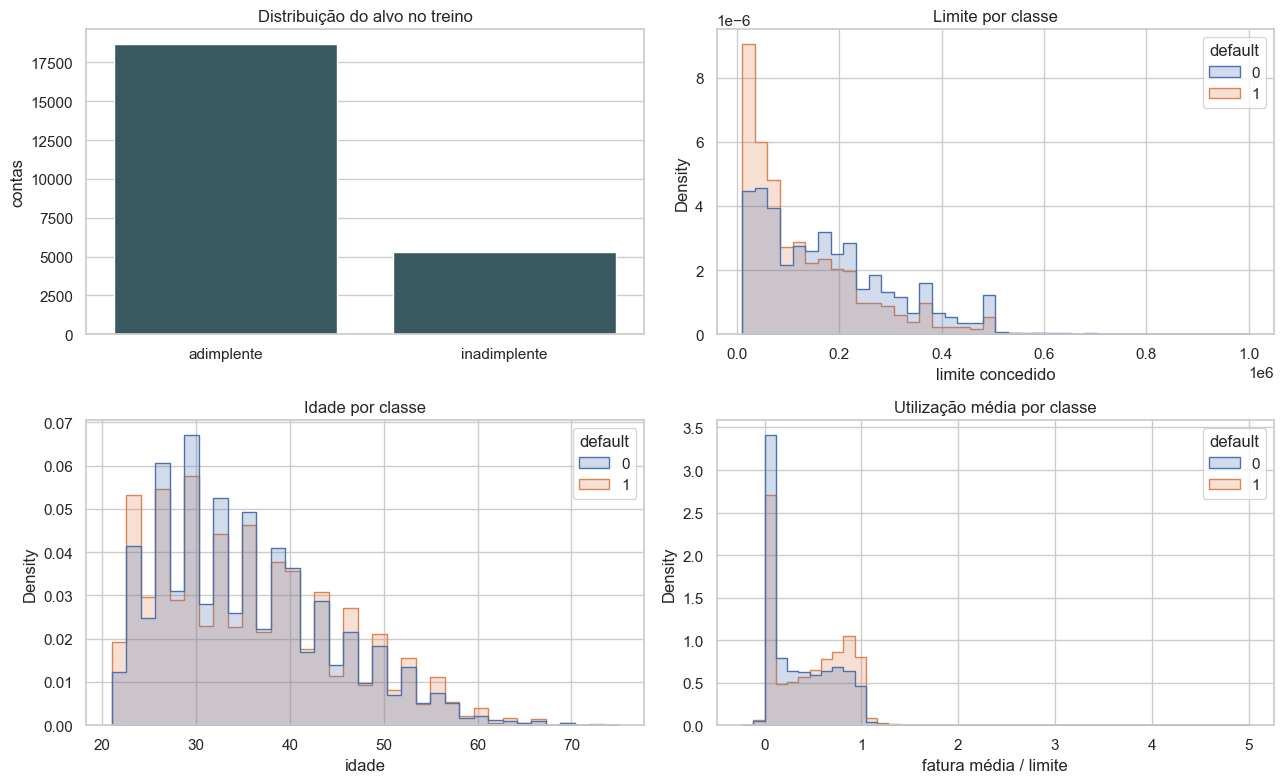

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.countplot(x=y_train.map({0: "adimplente", 1: "inadimplente"}), ax=axes[0, 0], color="#335C67")
axes[0, 0].set_title("Distribuição do alvo no treino")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("contas")

sns.histplot(data=train_eng.assign(default=y_train), x="LIMIT_BAL", hue="default",
             stat="density", common_norm=False, bins=40, element="step", ax=axes[0, 1])
axes[0, 1].set_title("Limite por classe")
axes[0, 1].set_xlabel("limite concedido")

sns.histplot(data=train_eng.assign(default=y_train), x="AGE", hue="default",
             stat="density", common_norm=False, bins=35, element="step", ax=axes[1, 0])
axes[1, 0].set_title("Idade por classe")
axes[1, 0].set_xlabel("idade")

sns.histplot(data=train_eng.assign(default=y_train), x="UTILIZATION_MEAN", hue="default",
             stat="density", common_norm=False, bins=45, element="step", ax=axes[1, 1])
axes[1, 1].set_title("Utilização média por classe")
axes[1, 1].set_xlabel("fatura média / limite")

plt.tight_layout()
plt.show()

### Leitura dos gráficos

A prevalência torna o problema desbalanceado, mas não raro a ponto de exigir reamostragem automática. Limite e utilização separam parcialmente as classes; as distribuições ainda se sobrepõem, então regras univariadas serão insuficientes. Idade mostra diferenças menores e sugere que uma curva pode ser mais plausível que uma reta rígida.

SMOTE e oversampling não serão usados. Duplicar ou sintetizar inadimplentes altera a prevalência vista pelo modelo e pode prejudicar a interpretação da saída como PD. O projeto tratará o desbalanceamento com métricas adequadas e limiar orientado a custo. Reamostragem pode ser testada em outro desenho, sempre dentro dos folds e seguida de verificação de calibração.

### 6.1 Taxa empírica e regressão local

A regressão local ajusta uma pequena reta ao redor de cada ponto da grade, dando maior peso às observações próximas. Ela será usada como lente exploratória, não como artefato de produção.

<!-- DIDATICA-END-TO-END:regressao-local -->

### Objetivo da regressão local

A curva local funciona como diagnóstico de forma. O parâmetro `span` controla o compromisso entre uma curva muito irregular, sensível a ruído, e uma curva excessivamente lisa, incapaz de revelar estrutura.

**Bordas.** Nas extremidades há menos vizinhos dos dois lados, por isso o ajuste local fica mais instável. Decisões de política baseadas em caudas precisam de contagem de casos, intervalos de incerteza e regras de extrapolação.

**Comparação com o GAM.** A regressão local oferece uma referência visual sem exigir uma forma global. O GAM entrega uma função paramétrica por bases, regularizada e integrada ao pipeline. Concordância entre as duas curvas aumenta confiança na forma; divergência pede investigação.

**Leitura comercial.** Um pico local pode refletir mistura de segmentos, política histórica ou poucos casos. Ele gera hipótese para análise, não uma regra automática de corte.

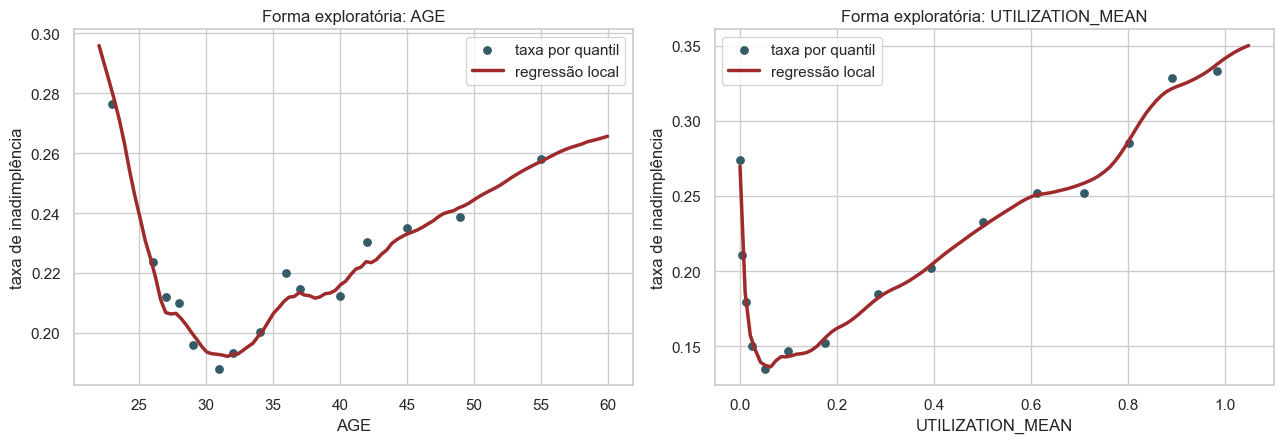

In [8]:
def loess_1d(x, y, grid, span=0.25):
    # Regressão local linear com pesos tricúbicos.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    grid = np.asarray(grid, dtype=float)
    n_neighbors = max(40, int(np.ceil(span * len(x))))
    fitted = []

    for x0 in grid:
        distance = np.abs(x - x0)
        h = np.partition(distance, n_neighbors - 1)[n_neighbors - 1]
        h = max(h, np.finfo(float).eps)
        u = distance / h
        weights = np.where(u < 1, (1 - u**3) ** 3, 0.0)
        design = np.column_stack([np.ones_like(x), x - x0])
        xtw = design.T * weights
        beta = np.linalg.pinv(xtw @ design) @ (xtw @ y)
        fitted.append(beta[0])
    return np.clip(np.asarray(fitted), 0, 1)


def empirical_bins(frame, target, feature, q=15):
    temp = pd.DataFrame({feature: frame[feature], "target": target})
    temp["bin"] = pd.qcut(temp[feature], q=q, duplicates="drop")
    return temp.groupby("bin", observed=True).agg(
        x=(feature, "median"),
        default_rate=("target", "mean"),
        n=("target", "size"),
    ).reset_index(drop=True)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, feature, span in [
    (axes[0], "AGE", 0.22),
    (axes[1], "UTILIZATION_MEAN", 0.18),
]:
    observed = empirical_bins(train_eng, y_train, feature)
    lo, hi = train_eng[feature].quantile([0.01, 0.99])
    grid = np.linspace(lo, hi, 100)
    curve = loess_1d(train_eng[feature], y_train, grid, span=span)
    ax.scatter(observed["x"], observed["default_rate"], s=28, color="#335C67",
               label="taxa por quantil")
    ax.plot(grid, curve, color="#9E2A2B", lw=2.5, label="regressão local")
    ax.set_title(f"Forma exploratória: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("taxa de inadimplência")
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
mask = (
    (y_train.eq(1)) &
    (train_eng["UTILIZATION_MEAN"].le(0.05))
)

clientes_filtrados = train_eng.loc[mask].copy()
clientes_filtrados["DEFAULT"] = y_train.loc[mask]

display(clientes_filtrados)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,UTILIZATION_MEAN,PAYMENT_TO_BILL,BILL_TREND,DELAY_MONTHS,MAX_DELAY,DEFAULT
4102,240000,2,1,2,36,-1,-1,2,0,-1,2,5367,6959,6649,5149,13750,5777,6959,15,0,7013,0,726,0.0303,0.3295,-0.0017,2,2,1
4144,200000,2,1,2,42,-1,-1,2,-1,-1,-1,660,1320,660,1320,1320,1710,1320,0,1320,1320,1710,27077,0.0058,4.0985,-0.0053,1,2,1
173,50000,2,1,2,24,1,-2,-2,-2,-2,-2,-709,-709,-709,-2898,-3272,-3272,0,0,0,0,0,0,-0.0386,0.0000,0.0513,1,1,1
23641,180000,2,1,2,35,1,-2,-2,-2,-2,-2,-18,-18,-18,-18,-18,-18,0,0,0,0,0,0,-0.0001,0.0000,0.0000,1,1,1
26533,450000,2,3,1,56,1,-1,-1,-1,-1,-1,-4,831,-3,646,-2,418,835,0,649,0,420,1204,0.0007,1.0736,-0.0009,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26284,320000,2,2,1,42,-1,-1,-2,-2,-2,-2,8144,0,0,0,0,0,0,0,0,0,0,0,0.0042,0.0000,0.0255,0,-1,1
10008,360000,2,1,1,48,1,-1,-1,-2,-2,-2,491,3670,-114,-200,-200,-200,3700,0,0,0,0,0,0.0016,0.7169,0.0019,1,1,1
13232,100000,1,2,2,32,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,1,1,1
23654,160000,2,2,1,36,-2,-2,-2,-2,-2,-2,-20,-20,3640,2935,1603,14129,0,3660,3135,1650,14200,1500,0.0232,1.0360,-0.0884,0,-2,1


### Pergunta didática 3

Por que a curva local não pode ser lida como efeito causal da utilização sobre a inadimplência?

<details>
<summary>Resposta guiada</summary>

A curva é marginal e observacional. Clientes com utilização diferente também diferem em limite, atraso, renda não observada, política de crédito e outras características. A associação ajuda a especificar o preditor; ela não estima o que ocorreria se a instituição alterasse somente a utilização de uma mesma pessoa.

</details>

## 7. Baseline e pipelines das quatro famílias

As mesmas variáveis lineares e categóricas aparecem em todas as famílias. Apenas quatro termos focais mudam de representação: idade, limite, utilização média e pagamento sobre fatura.

`SEX` fica fora do preditor. Os status mensais de pagamento entram como categorias porque a distância entre códigos não deve ser assumida linear. Categorias desconhecidas em produção são ignoradas pelo one-hot, mas devem gerar alerta de monitoramento.

<!-- DIDATICA-END-TO-END:pipelines-modelos -->

### Decisões técnicas do pipeline

O baseline com a prevalência responde à pergunta mínima: o modelo aprende algo além de repetir a taxa média? Cada família recebe a mesma informação e muda apenas a representação dos quatro termos focais, permitindo uma comparação mais justa.

**Pipeline.** Imputação, escala, faixas, nós e one-hot são aprendidos dentro de cada `fit`. Se qualquer transformação fosse ajustada antes da validação, as estatísticas das dobras de validação entrariam no treinamento.

**Status como categoria.** Os códigos de pagamento possuem ordem parcial e significados próprios. One-hot evita supor que a diferença entre `-2` e `-1` tenha o mesmo efeito da diferença entre `1` e `2`.

**Regularização.** `C` menor aumenta a penalização e reduz coeficientes. Com muitas bases e categorias, essa restrição protege contra ajustes instáveis. O melhor valor depende do desenho de validação.

**Leitura comercial.** O pipeline reduz divergência entre desenvolvimento e scoring. Ele também torna explícito o contrato de entrada, requisito para SLA, testes de origem, auditoria e rollback.

In [10]:
FOCUS_FEATURES = ["AGE", "LIMIT_BAL", "UTILIZATION_MEAN", "PAYMENT_TO_BILL"]
LINEAR_FEATURES = [
    *[f"BILL_AMT{i}" for i in range(1, 7)],
    *[f"PAY_AMT{i}" for i in range(1, 7)],
    "BILL_TREND", "DELAY_MONTHS", "MAX_DELAY",
]
CATEGORICAL_FEATURES = [
    "EDUCATION", "MARRIAGE", *[f"PAY_{i}" for i in range(1, 7)]
]


def build_pipeline(kind="linear"):
    if kind == "linear":
        focus_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ])
    elif kind == "step":
        focus_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("bins", KBinsDiscretizer(n_bins=6, encode="onehot", strategy="quantile")),
        ])
    elif kind == "poly":
        focus_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale_before", StandardScaler()),
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("scale_after", StandardScaler(with_mean=False)),
        ])
    elif kind == "gam":
        focus_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("spline", SplineTransformer(
                n_knots=6,
                degree=3,
                knots="quantile",
                include_bias=False,
                extrapolation="linear",
            )),
            ("scale", StandardScaler()),
        ])
    else:
        raise ValueError(f"Família desconhecida: {kind}")

    linear_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("focus", focus_transformer, FOCUS_FEATURES),
        ("linear", linear_transformer, LINEAR_FEATURES),
        ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
    ], sparse_threshold=1.0)

    return Pipeline([
        ("features", CreditFeatureEngineer()),
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1_000,
            random_state=SEED,
        )),
    ])


candidate_grids = {
    "linear": {
        "model__C": [0.05, 0.20, 1.00],
    },
    "step": {
        "preprocess__focus__bins__n_bins": [4, 8],
        "model__C": [0.10, 1.00],
    },
    "poly": {
        "preprocess__focus__poly__degree": [2, 3],
        "model__C": [0.05, 0.20, 1.00],
    },
    "gam": {
        "preprocess__focus__spline__n_knots": [4, 7, 10],
        "model__C": [0.10, 1.00],
    },
}

model_map = {
    "linear": "Logística linear",
    "step": "Função degrau",
    "poly": "Polinômio",
    "gam": "GAM com B-splines",
}

display(build_pipeline("gam"))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('focus', ...), ('linear', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

### Por que padronizar antes do polinômio?

Elevar `LIMIT_BAL` ao cubo gera números de escala muito maior que os demais termos. A primeira padronização estabiliza a construção dos produtos; a segunda coloca as colunas expandidas em escala comparável para a penalização L2.

### Por que nós em quantis para as splines?

Os quantis distribuem nós onde há dados. Nós igualmente espaçados desperdiçariam parte da flexibilidade em caudas com poucas observações. A extrapolação linear reduz curvas explosivas fora do intervalo visto no treino, mas não autoriza extrapolação sem monitoramento.

In [11]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_probability = dummy.predict_proba(np.zeros((len(y_train), 1)))[:, 1]

baseline = pd.Series({
    "prevalência": y_train.mean(),
    "log loss do prior": log_loss(y_train, dummy_probability),
    "Brier do prior": brier_score_loss(y_train, dummy_probability),
    "ROC AUC do prior": roc_auc_score(y_train, dummy_probability),
})
baseline.to_frame("baseline")

,baseline
prevalência,0.2212
log loss do prior,0.5284
Brier do prior,0.1723
ROC AUC do prior,0.5000


## 8. Seleção por validação cruzada aninhada

A busca interna escolhe grau, número de faixas, quantidade de nós e regularização. A dobra externa mede o procedimento completo em dados que não participaram dessa escolha.

O teste final continua fechado.

Regra de decisão declarada antes de observar o teste:

1. minimizar log loss médio nas dobras externas;
2. considerar tecnicamente empatados os modelos dentro de um erro-padrão do melhor log loss;
3. entre os empatados, exigir AUC a menos de 0,002 do melhor valor;
4. se função degrau e GAM permanecerem, escolher o GAM por continuidade da PD e ausência de cortes artificiais.

Essa regra explicita que seleção de modelo contém julgamento estatístico e operacional. A terceira casa decimal não deve mandar sozinha na arquitetura.

<!-- DIDATICA-END-TO-END:validacao-aninhada -->

### O que a validação aninhada mede

A busca interna escolhe hiperparâmetros. A dobra externa mede o resultado de todo esse processo em uma partição que não influenciou a escolha. Sem o laço externo, a melhor combinação herdaria parte do ruído da busca.

**Por que log loss é primária.** O objetivo é produzir PD. Log loss avalia a distribuição probabilística e pune confiança errada. AUC e Gini medem ordenação; Brier mede erro quadrático; average precision concentra a análise nos inadimplentes; KS mede separação máxima.

**Incerteza.** Três dobras externas fornecem uma estimativa didática com custo computacional controlado. Em uma validação formal, a estratégia deve refletir tempo, safras e grupos, com mais repetições quando viável. Diferenças menores que a variação entre dobras não sustentam superioridade forte.

**Leitura comercial.** A métrica primária deve acompanhar o uso. Priorização pode favorecer ranking; precificação e perda esperada exigem calibração; cobrança com capacidade fixa precisa de ganho no topo da lista. Um único placar não responde a todos esses usos.

In [15]:
def probability_metrics(y_true, probability):
    fpr, tpr, _ = roc_curve(y_true, probability)
    auc = roc_auc_score(y_true, probability)
    return {
        "roc_auc": auc,
        "gini": 2 * auc - 1,
        "average_precision": average_precision_score(y_true, probability),
        "log_loss": log_loss(y_true, probability),
        "brier": brier_score_loss(y_true, probability),
        "ks": np.max(tpr - fpr),
    }


outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED + 1)

cv_records = []
start = time.perf_counter()

for kind, param_grid in candidate_grids.items():
    for fold, (fit_idx, valid_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        search = GridSearchCV(
            estimator=build_pipeline(kind),
            param_grid=param_grid,
            scoring="neg_log_loss",
            cv=inner_cv,
            refit=True,
            n_jobs=1,
        )
        search.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        probability = search.predict_proba(X_train.iloc[valid_idx])[:, 1]
        row = {
            "kind": kind,
            "modelo": model_map[kind],
            "fold": fold,
            "best_params": search.best_params_,
            **probability_metrics(y_train.iloc[valid_idx], probability),
        }
        cv_records.append(row)

cv_results = pd.DataFrame(cv_records)
elapsed_cv = time.perf_counter() - start
print(f"Validação aninhada concluída em {elapsed_cv:.1f} s")
cv_results.head(8)

Validação aninhada concluída em 52.5 s


,kind,modelo,fold,best_params,roc_auc,gini,average_precision,log_loss,brier,ks
0,linear,Logística linear,1,{'model__C': 0.2},0.7733,0.5467,0.5534,0.4307,0.1344,0.4341
1,linear,Logística linear,2,{'model__C': 0.2},0.7646,0.5292,0.5310,0.4414,0.1379,0.4032
2,linear,Logística linear,3,{'model__C': 0.05},0.7776,0.5552,0.5465,0.4312,0.1347,0.4317
3,step,Função degrau,1,"{'model__C': 0.1, 'preprocess__focus__bins__n_...",0.7792,0.5583,0.5541,0.4280,0.1336,0.4354
4,step,Função degrau,2,"{'model__C': 0.1, 'preprocess__focus__bins__n_...",0.7689,0.5379,0.5301,0.4387,0.1374,0.4128
5,step,Função degrau,3,"{'model__C': 0.1, 'preprocess__focus__bins__n_...",0.7854,0.5709,0.5505,0.4273,0.1338,0.4319
6,poly,Polinômio,1,"{'model__C': 0.2, 'preprocess__focus__poly__de...",0.7763,0.5526,0.5527,0.4306,0.1343,0.4281
7,poly,Polinômio,2,"{'model__C': 0.2, 'preprocess__focus__poly__de...",0.7683,0.5367,0.5333,0.4398,0.1375,0.4051


In [16]:
cv_summary = (
    cv_results.groupby(["kind", "modelo"], as_index=False)
    .agg(
        log_loss_mean=("log_loss", "mean"),
        log_loss_sd=("log_loss", "std"),
        auc_mean=("roc_auc", "mean"),
        auc_sd=("roc_auc", "std"),
        ap_mean=("average_precision", "mean"),
        brier_mean=("brier", "mean"),
        gini_mean=("gini", "mean"),
        ks_mean=("ks", "mean"),
    )
)
cv_summary["log_loss_se"] = cv_summary["log_loss_sd"] / np.sqrt(outer_cv.n_splits)
cv_summary = cv_summary.sort_values("log_loss_mean").reset_index(drop=True)
cv_summary

,kind,modelo,log_loss_mean,log_loss_sd,auc_mean,auc_sd,ap_mean,brier_mean,gini_mean,ks_mean,log_loss_se
0,step,Função degrau,0.4313,0.0064,0.7778,0.0083,0.5449,0.1349,0.5557,0.4267,0.0037
1,gam,GAM com B-splines,0.4318,0.0045,0.7798,0.0067,0.5453,0.1351,0.5595,0.4257,0.0026
2,poly,Polinômio,0.4333,0.0057,0.7752,0.0065,0.5444,0.1354,0.5505,0.4217,0.0033
3,linear,Logística linear,0.4344,0.0061,0.7719,0.0066,0.5436,0.1356,0.5437,0.4230,0.0035


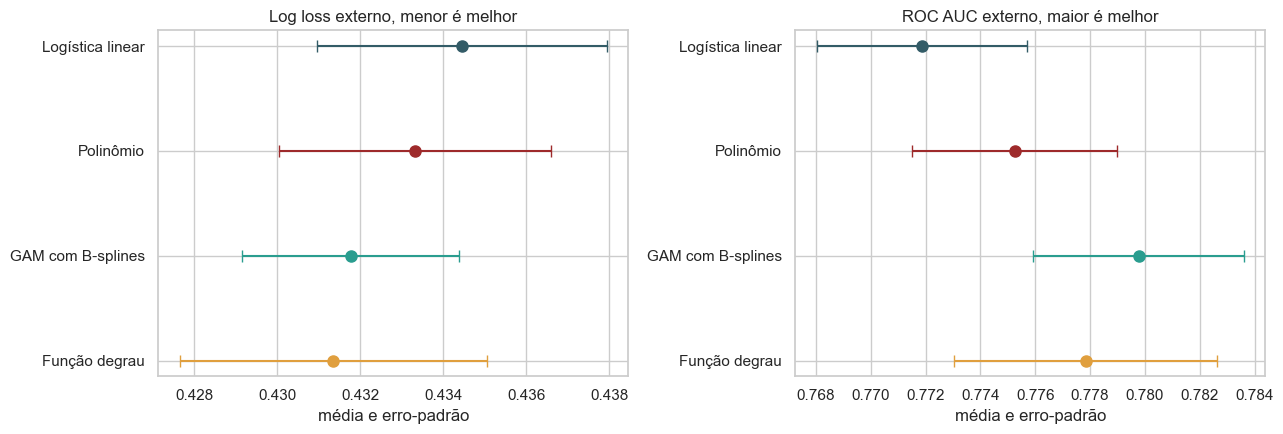

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = cv_summary["kind"].tolist()
for _, row in cv_summary.iterrows():
    axes[0].errorbar(
        row["log_loss_mean"], row["modelo"], xerr=row["log_loss_se"],
        fmt="o", capsize=4, color=COLORS[row["kind"]], markersize=8
    )
    axes[1].errorbar(
        row["auc_mean"], row["modelo"], xerr=row["auc_sd"] / np.sqrt(outer_cv.n_splits),
        fmt="o", capsize=4, color=COLORS[row["kind"]], markersize=8
    )

axes[0].set_title("Log loss externo, menor é melhor")
axes[0].set_xlabel("média e erro-padrão")
axes[0].set_ylabel("")
axes[1].set_title("ROC AUC externo, maior é melhor")
axes[1].set_xlabel("média e erro-padrão")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [18]:
best_logloss_row = cv_summary.iloc[0]
logloss_limit = best_logloss_row["log_loss_mean"] + best_logloss_row["log_loss_se"]
auc_limit = cv_summary["auc_mean"].max() - 0.002

eligible = cv_summary[
    (cv_summary["log_loss_mean"] <= logloss_limit)
    & (cv_summary["auc_mean"] >= auc_limit)
].copy()

if "gam" in eligible["kind"].values:
    selected_kind = "gam"
else:
    selected_kind = eligible.sort_values("log_loss_mean").iloc[0]["kind"]

display(Markdown(
    f"**Família escolhida:** {model_map[selected_kind]}.  "
    f"Limite de empate no log loss: `{logloss_limit:.5f}`. "
    f"Limite de AUC: `{auc_limit:.5f}`."
))
eligible[["modelo", "log_loss_mean", "log_loss_se", "auc_mean", "brier_mean"]]

**Família escolhida:** GAM com B-splines.  Limite de empate no log loss: `0.43504`. Limite de AUC: `0.77777`.

,modelo,log_loss_mean,log_loss_se,auc_mean,brier_mean
0,Função degrau,0.4313,0.0037,0.7778,0.1349
1,GAM com B-splines,0.4318,0.0026,0.7798,0.1351


### Leitura da comparação

O modelo linear fornece o referencial de viés. Se funções flexíveis melhoram log loss e AUC nas dobras externas, há evidência de que a forma linear deixa estrutura preditiva sem modelar. Uma diferença pequena, comparada ao erro-padrão, não justifica escolher o objeto mais complexo apenas porque ele ficou em primeiro por poucos décimos de ponto percentual.

A função degrau pode competir bem porque os atrasos e políticas de crédito já produzem comportamento por faixas. Para uma PD usada em políticas sensíveis a pequenas mudanças, saltos nas bordas criam casos quase iguais com respostas diferentes. O GAM preserva flexibilidade e continuidade.

### Pergunta didática 4

Por que o desempenho médio da melhor configuração na busca interna seria otimista como estimativa final?

<details>
<summary>Resposta guiada</summary>

A mesma validação interna escolheu a configuração e mediu seu desempenho. Entre várias tentativas, alguma se beneficia do ruído das dobras. O laço externo avalia o procedimento de busca em observações que não participaram dessa escolha.

</details>

## 9. Reajuste no treino completo

Depois da escolha da família, uma busca interna final usa todo o treino para definir os hiperparâmetros que irão para o artefato. O teste ainda não participa.

<!-- DIDATICA-END-TO-END:reajuste -->

### Por que reajustar depois da seleção

Durante a validação, cada modelo usa apenas parte do treino. Depois que família e espaço de busca estão definidos, o reajuste aproveita todo o treino disponível para estimar a versão final.

O teste permanece excluído. Incorporá-lo ao fit melhoraria artificialmente a métrica final e eliminaria a única estimativa independente do projeto.

**Leitura dos hiperparâmetros.** Sete nós permitem curvatura local moderada nos quatro atributos focais. `C=0,1` aplica regularização relativamente forte, coerente com o número de bases e categorias. Esses valores são resultado da amostra e precisam ser revalidados em outra população.

**Leitura comercial.** Esse é o ponto de congelamento: código, dados, parâmetros, limiar, métricas e versão passam a formar uma unidade de aprovação. Alterar qualquer elemento cria uma nova versão do modelo.

In [19]:
fitted_searches = {}

for kind, param_grid in candidate_grids.items():
    search = GridSearchCV(
        build_pipeline(kind),
        param_grid=param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=1,
    )
    search.fit(X_train, y_train)
    fitted_searches[kind] = search

final_search = fitted_searches[selected_kind]
final_model = final_search.best_estimator_

transformed_train = final_model.named_steps["preprocess"].transform(
    final_model.named_steps["features"].transform(X_train.iloc[:500])
)

fit_summary = pd.Series({
    "família": model_map[selected_kind],
    "melhores hiperparâmetros": final_search.best_params_,
    "log loss interno": -final_search.best_score_,
    "número de colunas após transformação": transformed_train.shape[1],
})
fit_summary.to_frame("resultado")

,resultado
família,GAM com B-splines
melhores hiperparâmetros,"{'model__C': 0.1, 'preprocess__focus__spline__..."
log loss interno,0.4313
número de colunas após transformação,118


## 10. Como as famílias alteram a curva de PD

As curvas abaixo variam uma característica e mantêm as demais em um cliente real próximo da PD mediana. Elas mostram comportamento preditivo condicional ao perfil de referência. Não são curvas causais.

Ao variar o limite, as faturas são escaladas na mesma proporção para manter aproximadamente constante a utilização do perfil. Isso evita confundir o efeito do limite com uma mudança mecânica da razão fatura/limite.

<!-- DIDATICA-END-TO-END:curvas-pd -->

### Como interpretar as curvas condicionais

Cada linha mostra a PD para um perfil de referência enquanto uma variável é alterada. Esse desenho facilita comparação de forma, mas depende do cliente escolhido e pode criar combinações pouco comuns.

**Função degrau.** A curva evidencia estabilidade dentro das faixas e saltos nos limites. O resultado pode ser útil quando a própria política trabalha por bandas, porém cria risco de arbitragem e tratamento diferente perto do corte.

**Polinômio.** A curva global pode crescer rapidamente nas bordas, pois os termos de grau alto dominam fora da região central. O comportamento deve ser verificado dentro e fora da faixa observada.

**GAM.** A flexibilidade local reduz influência de uma região sobre todo o domínio. A curva ainda pode oscilar quando há poucos casos ou penalização fraca.

**Leitura comercial.** Um gráfico parcial serve para contestar o modelo com conhecimento de negócio e detectar respostas absurdas. Ele não deve ser convertido diretamente em aumento ou redução de limite, porque a relação permanece preditiva e observacional.

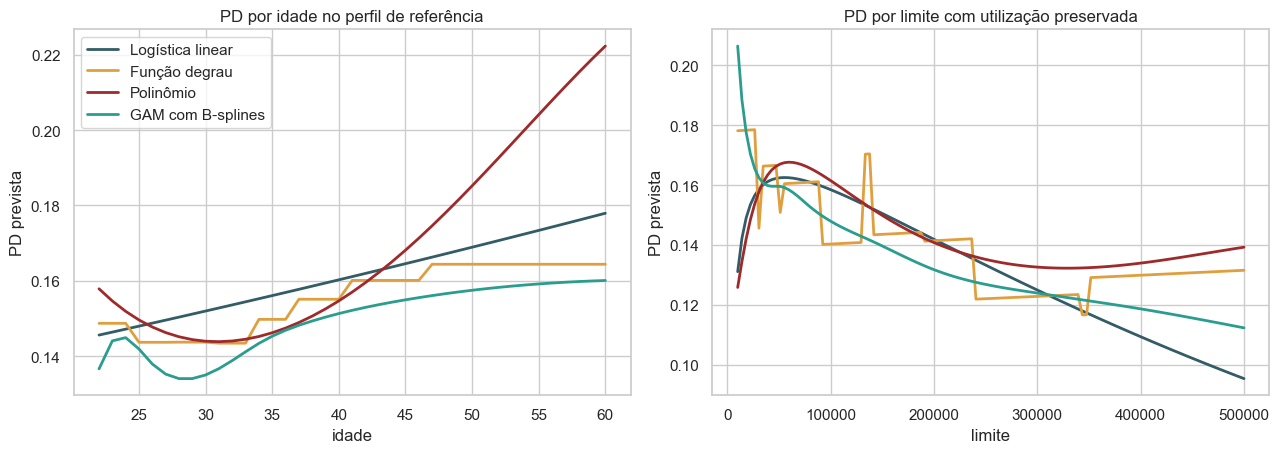

In [20]:
reference_probabilities = final_model.predict_proba(X_train)[:, 1]
median_probability = np.median(reference_probabilities)
reference_position = np.argmin(np.abs(reference_probabilities - median_probability))
reference_row = X_train.iloc[[reference_position]].copy()


def profile_rows(reference, feature, values):
    rows = pd.concat([reference] * len(values), ignore_index=True)
    values = np.asarray(values)
    if feature == "LIMIT_BAL":
        old_limit = float(reference["LIMIT_BAL"].iloc[0])
        ratio = values / old_limit
        for col in [f"BILL_AMT{i}" for i in range(1, 7)]:
            rows[col] = float(reference[col].iloc[0]) * ratio
    rows[feature] = values
    return rows


age_grid = np.arange(
    int(X_train["AGE"].quantile(0.01)),
    int(X_train["AGE"].quantile(0.99)) + 1,
)
limit_grid = np.linspace(
    X_train["LIMIT_BAL"].quantile(0.01),
    X_train["LIMIT_BAL"].quantile(0.99),
    120,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
for kind, search in fitted_searches.items():
    for ax, feature, grid in [
        (axes[0], "AGE", age_grid),
        (axes[1], "LIMIT_BAL", limit_grid),
    ]:
        rows = profile_rows(reference_row, feature, grid)
        probability = search.best_estimator_.predict_proba(rows)[:, 1]
        ax.plot(grid, probability, lw=2, color=COLORS[kind], label=model_map[kind])

axes[0].set_title("PD por idade no perfil de referência")
axes[0].set_xlabel("idade")
axes[0].set_ylabel("PD prevista")
axes[1].set_title("PD por limite com utilização preservada")
axes[1].set_xlabel("limite")
axes[1].set_ylabel("PD prevista")
axes[1].ticklabel_format(style="plain", axis="x")
axes[0].legend()
plt.tight_layout()
plt.show()

### Interpretação das formas

- A logística linear impõe variação monotônica do logit por unidade padronizada.
- A função degrau fica constante dentro da faixa e salta no corte. Duas contas quase idênticas podem receber PDs distintas por poucos reais ou um ano de diferença.
- O polinômio usa uma única equação global. Curvatura em uma região influencia todo o domínio e pode se tornar instável nas bordas.
- O GAM combina bases locais. Cada nó altera principalmente uma região, enquanto a penalização reduz oscilações excessivas.

O gráfico também serve como teste de sanidade. Uma curva numericamente boa pode contrariar conhecimento de negócio, extrapolar mal ou criar descontinuidades incompatíveis com a política.

## 11. Escolha do limiar sem tocar no teste

O modelo produz uma PD. Transformá-la em ação exige custos, capacidade operacional e apetite a risco.

Hipótese didática de custo:

- falso negativo, inadimplente não sinalizado: 5 unidades;
- falso positivo, adimplente sinalizado: 1 unidade.

O valor 5 não representa uma instituição real. Em produção, o custo deveria incorporar exposição, LGD, margem, recuperação, custo de revisão e restrições de capacidade.

<!-- DIDATICA-END-TO-END:limiar -->

### Modelo e política de decisão

A PD ordena e quantifica risco. O limiar traduz essa saída em ação com base em custo e capacidade. Trocar o limiar muda precision, recall e volume sinalizado sem alterar os coeficientes.

**Previsões OOF.** O limiar é calculado com probabilidades fora da amostra dentro do treino. Usar probabilidades do próprio fit produziria custos excessivamente otimistas.

**Hipótese de custo.** A razão 5 para 1 reduz o limiar porque deixar um inadimplente sem ação é considerado mais caro. O ótimo de aproximadamente 0,162 pertence a essa hipótese e a esta amostra. Uma razão diferente produziria outra política.

**Capacidade.** Se a operação consegue revisar apenas 20% das contas, a restrição de volume pode dominar o custo teórico. Nesse caso, a política usa quantil de PD, ganho no topo e retorno incremental.

**Leitura comercial.** Falso positivo pode significar atrito, perda de receita ou tratamento desnecessário. Falso negativo pode gerar perda financeira. A matriz de custo precisa ser construída com as áreas que assumem essas consequências.

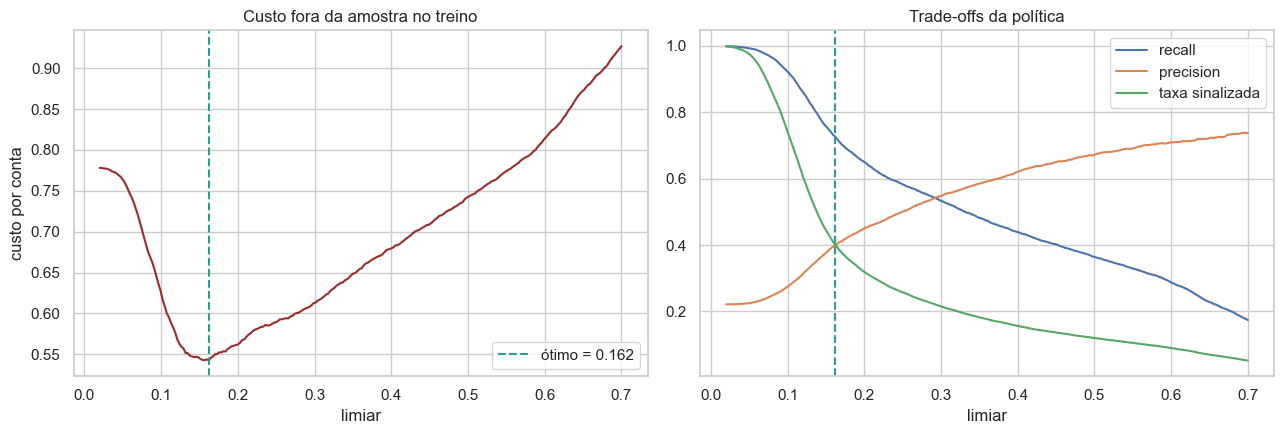

,threshold,tn,fp,fn,tp,precision,recall,flag_rate,cost_per_account
52,0.1620,12919,5772,1449,3860,0.4007,0.7271,0.4013,0.5424


In [21]:
oof_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 2)
oof_probability = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=oof_cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]


def decision_table(y_true, probability, thresholds, cost_fn=5.0, cost_fp=1.0):
    rows = []
    y_array = np.asarray(y_true)
    for threshold in thresholds:
        pred = (probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_array, pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold": threshold,
            "tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "precision": precision_score(y_array, pred, zero_division=0),
            "recall": recall_score(y_array, pred, zero_division=0),
            "flag_rate": pred.mean(),
            "cost_per_account": (cost_fn * fn + cost_fp * fp) / len(y_array),
        })
    return pd.DataFrame(rows)


threshold_grid = np.linspace(0.02, 0.70, 250)
oof_decisions = decision_table(y_train, oof_probability, threshold_grid)
best_threshold = float(
    oof_decisions.loc[oof_decisions["cost_per_account"].idxmin(), "threshold"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(oof_decisions["threshold"], oof_decisions["cost_per_account"], color="#9E2A2B")
axes[0].axvline(best_threshold, color="#2A9D8F", ls="--", label=f"ótimo = {best_threshold:.3f}")
axes[0].set_title("Custo fora da amostra no treino")
axes[0].set_xlabel("limiar")
axes[0].set_ylabel("custo por conta")
axes[0].legend()

axes[1].plot(oof_decisions["threshold"], oof_decisions["recall"], label="recall")
axes[1].plot(oof_decisions["threshold"], oof_decisions["precision"], label="precision")
axes[1].plot(oof_decisions["threshold"], oof_decisions["flag_rate"], label="taxa sinalizada")
axes[1].axvline(best_threshold, color="#2A9D8F", ls="--")
axes[1].set_title("Trade-offs da política")
axes[1].set_xlabel("limiar")
axes[1].legend()

plt.tight_layout()
plt.show()

oof_decisions.iloc[(oof_decisions["threshold"] - best_threshold).abs().argsort()[:1]]

### Pergunta didática 5

O que ocorre com o limiar ótimo se o custo do falso negativo sobe de 5 para 10, mantendo os demais fatores?

<details>
<summary>Resposta guiada</summary>

O limiar tende a cair. Mais contas serão sinalizadas, o recall de inadimplentes sobe e a quantidade de falsos positivos também. A mudança altera a política de ação, sem exigir que o classificador seja retreinado.

</details>

## 12. Abertura única do teste

Agora o pipeline, os hiperparâmetros e o limiar estão definidos. O teste será usado uma vez para estimar o desempenho final dessa solução congelada.

<!-- DIDATICA-END-TO-END:teste-final -->

### Papel da avaliação final

O teste responde quanto a solução congelada generaliza para uma amostra independente da mesma população histórica. O intervalo bootstrap mostra a incerteza amostral das métricas e impede tratar o valor pontual como exato.

**Leitura dos resultados.** AUC de aproximadamente 0,770 e Gini de 0,540 indicam capacidade de ordenação relevante frente ao acaso. Log loss de 0,437 e Brier de 0,137 melhoram os baselines baseados apenas na prevalência. Essa comparação mostra ganho preditivo, sem estabelecer retorno financeiro.

**Regra de governança.** O resultado do teste deve levar a aprovação, rejeição ou abertura formal de uma nova versão. Ajustar nós, variáveis ou limiar depois de ver essa saída exige outro conjunto independente para avaliação.

**Limitação comercial.** O split aleatório não mede deterioração macroeconômica nem mudança de política. Antes de implantação, faltam validação temporal, análise por safra, estabilidade e estimativa monetária.

In [22]:
test_probability = final_model.predict_proba(X_test)[:, 1]
test_metrics = probability_metrics(y_test, test_probability)


def bootstrap_interval(y_true, probability, metric_fn, n_boot=500, seed=SEED):
    rng = np.random.default_rng(seed)
    y_array = np.asarray(y_true)
    p_array = np.asarray(probability)
    estimates = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_array), len(y_array))
        if np.unique(y_array[idx]).size < 2:
            continue
        estimates.append(metric_fn(y_array[idx], p_array[idx]))
    return np.quantile(estimates, [0.025, 0.975])


auc_ci = bootstrap_interval(y_test, test_probability, roc_auc_score)
logloss_ci = bootstrap_interval(y_test, test_probability, log_loss)

final_metric_table = pd.DataFrame({
    "métrica": ["ROC AUC", "Gini", "Average precision", "Log loss", "Brier", "KS"],
    "teste": [
        test_metrics["roc_auc"], test_metrics["gini"],
        test_metrics["average_precision"], test_metrics["log_loss"],
        test_metrics["brier"], test_metrics["ks"],
    ],
    "referência": [
        0.5, 0.0, y_test.mean(), baseline["log loss do prior"],
        baseline["Brier do prior"], 0.0,
    ],
})

print(f"IC bootstrap 95% da AUC: [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]")
print(f"IC bootstrap 95% do log loss: [{logloss_ci[0]:.4f}, {logloss_ci[1]:.4f}]")
final_metric_table

IC bootstrap 95% da AUC: [0.7563, 0.7870]
IC bootstrap 95% do log loss: [0.4223, 0.4519]


,métrica,teste,referência
0,ROC AUC,0.7702,0.5000
1,Gini,0.5404,0.0000
2,Average precision,0.5388,0.2212
3,Log loss,0.4368,0.5284
4,Brier,0.1373,0.1723
5,KS,0.4119,0.0000


In [23]:
model_log_loss = log_loss(
    y_train,
    oof_probability
)

prior_probability = np.full(
    len(y_train),
    y_train.mean()
)

prior_log_loss = log_loss(
    y_train,
    prior_probability
)

print(f"Prior: {prior_log_loss:.4f}")
print(f"Model: {model_log_loss:.4f}")

Prior: 0.5284
Model: 0.4312


In [24]:
threshold_grid = np.linspace(
    0.02,
    0.70,
    250
)

oof_decisions = decision_table(
    y_train,
    oof_probability,
    threshold_grid,
    cost_fn=5.0,
    cost_fp=1.0
)

best_threshold = float(
    oof_decisions.loc[
        oof_decisions["cost_per_account"].idxmin(),
        "threshold"
    ]
)

print(f"Best threshold: {best_threshold:.3f}")

Best threshold: 0.162


In [25]:
oof_decisions["specificity"] = (
    oof_decisions["tn"]
    /
    (
        oof_decisions["tn"]
        + oof_decisions["fp"]
    )
)

oof_decisions["f1"] = (
    2
    * oof_decisions["precision"]
    * oof_decisions["recall"]
    /
    (
        oof_decisions["precision"]
        + oof_decisions["recall"]
    )
).fillna(0)

oof_decisions["balanced_accuracy"] = (
    oof_decisions["recall"]
    + oof_decisions["specificity"]
) / 2

threshold_comparison = pd.DataFrame({
    "criterion": [
        "Minimum cost",
        "Maximum F1",
        "Maximum balanced accuracy",
        "Minimum 80% recall"
    ],
    "threshold": [
        oof_decisions.loc[
            oof_decisions["cost_per_account"].idxmin(),
            "threshold"
        ],
        oof_decisions.loc[
            oof_decisions["f1"].idxmax(),
            "threshold"
        ],
        oof_decisions.loc[
            oof_decisions["balanced_accuracy"].idxmax(),
            "threshold"
        ],
        oof_decisions[
            oof_decisions["recall"] >= 0.80
        ].loc[
            oof_decisions[
                oof_decisions["recall"] >= 0.80
            ]["flag_rate"].idxmin(),
            "threshold"
        ]
    ]
})

display(threshold_comparison)

,criterion,threshold
0,Minimum cost,0.1620
1,Maximum F1,0.2794
2,Maximum balanced accuracy,0.2002
3,Minimum 80% recall,0.1347


Métricas das probabilidades OOF
ROC AUC:           0.7802
Log loss:         0.4312
Log loss do prior:0.5284
Brier:            0.1350
Average precision:0.5467


,criterion,threshold,tn,fp,fn,tp,accuracy,precision,recall,specificity,f1,balanced_accuracy,false_positive_rate,flag_rate,ks,roc_auc,log_loss,brier,cost_per_account
0,Menor custo,0.1620,12919,5772,1449,3860,0.6991,0.4007,0.7271,0.6912,0.5167,0.7091,0.3088,0.4013,0.4183,0.7802,0.4312,0.1350,0.5424
1,Maior F1,0.2794,16083,2608,2363,2946,0.7929,0.5304,0.5549,0.8605,0.5424,0.7077,0.1395,0.2314,0.4154,0.7802,0.4312,0.1350,0.6010
2,Maior KS,0.2002,14484,4207,1857,3452,0.7473,0.4507,0.6502,0.7749,0.5324,0.7126,0.2251,0.3191,0.4251,0.7802,0.4312,0.1350,0.5622
3,Recall mínimo de 80%,0.1347,10544,8147,1017,4292,0.6182,0.3450,0.8084,0.5641,0.4837,0.6863,0.4359,0.5183,0.3726,0.7802,0.4312,0.1350,0.5513


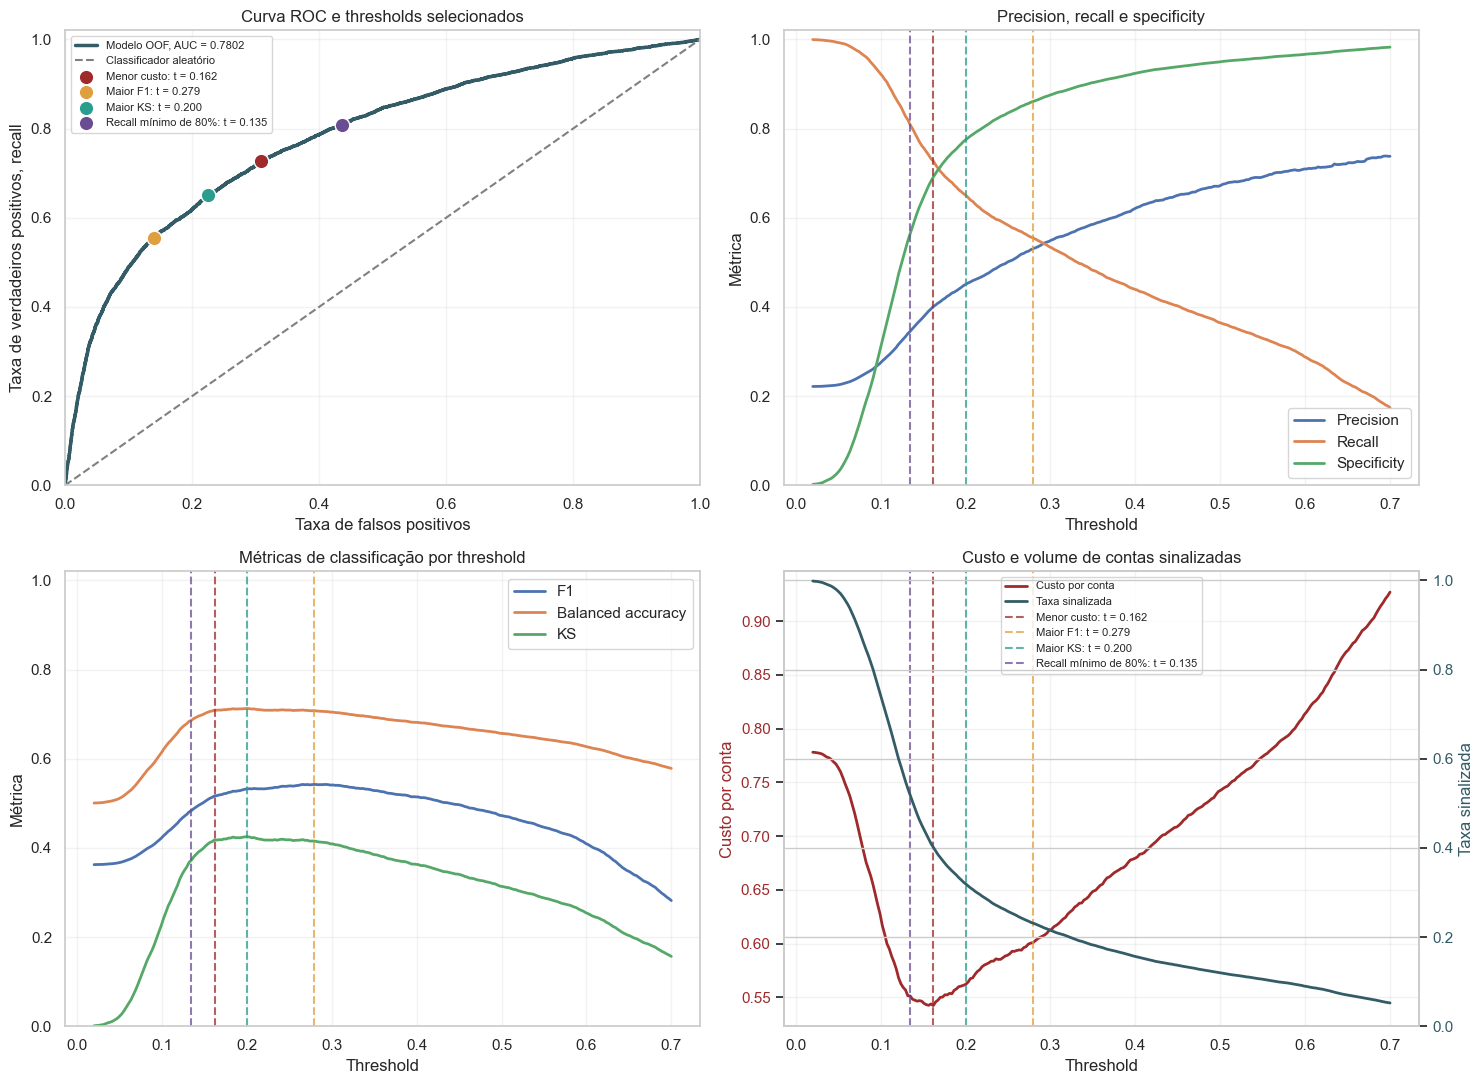

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    average_precision_score,
)


# ============================================================
# 1. Probabilidades fora da amostra dentro do treino
# ============================================================

oof_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED + 2
)

oof_probability = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=oof_cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]


# ============================================================
# 2. Função que calcula as métricas para cada threshold
# ============================================================

def create_decision_table(
    y_true,
    probability,
    thresholds,
    cost_fn=5.0,
    cost_fp=1.0
):

    rows = []

    y_array = np.asarray(y_true)

    for threshold in thresholds:

        prediction = (
            probability >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_array,
            prediction,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_array,
            prediction,
            zero_division=0
        )

        recall = recall_score(
            y_array,
            prediction,
            zero_division=0
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )

        false_positive_rate = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0
        )

        accuracy = (
            (tn + tp) / len(y_array)
        )

        if precision + recall > 0:

            f1 = (
                2
                * precision
                * recall
                / (precision + recall)
            )

        else:

            f1 = 0

        balanced_accuracy = (
            recall + specificity
        ) / 2

        ks = (
            recall
            - false_positive_rate
        )

        flag_rate = prediction.mean()

        cost_per_account = (
            cost_fn * fn
            + cost_fp * fp
        ) / len(y_array)

        rows.append({
            "threshold": threshold,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "specificity": specificity,
            "false_positive_rate": false_positive_rate,
            "f1": f1,
            "balanced_accuracy": balanced_accuracy,
            "ks": ks,
            "flag_rate": flag_rate,
            "cost_per_account": cost_per_account,
        })

    return pd.DataFrame(rows)


# ============================================================
# 3. Avaliação de 250 thresholds
# ============================================================

threshold_grid = np.linspace(
    0.02,
    0.70,
    250
)

decision_results = create_decision_table(
    y_true=y_train,
    probability=oof_probability,
    thresholds=threshold_grid,
    cost_fn=5.0,
    cost_fp=1.0
)


# ============================================================
# 4. Métricas gerais das probabilidades OOF
# ============================================================

model_auc = roc_auc_score(
    y_train,
    oof_probability
)

model_log_loss = log_loss(
    y_train,
    oof_probability
)

model_brier = brier_score_loss(
    y_train,
    oof_probability
)

model_average_precision = average_precision_score(
    y_train,
    oof_probability
)

prior_probability = np.full(
    len(y_train),
    y_train.mean()
)

prior_log_loss = log_loss(
    y_train,
    prior_probability
)

print("Métricas das probabilidades OOF")
print(f"ROC AUC:           {model_auc:.4f}")
print(f"Log loss:         {model_log_loss:.4f}")
print(f"Log loss do prior:{prior_log_loss:.4f}")
print(f"Brier:            {model_brier:.4f}")
print(
    f"Average precision:{model_average_precision:.4f}"
)


# ============================================================
# 5. Seleção dos thresholds
# ============================================================

selected_indices = {
    "Menor custo": (
        decision_results[
            "cost_per_account"
        ].idxmin()
    ),

    "Maior F1": (
        decision_results[
            "f1"
        ].idxmax()
    ),

    "Maior KS": (
        decision_results[
            "ks"
        ].idxmax()
    ),
}


# Recall mínimo desejado
minimum_recall = 0.80

eligible_recall = decision_results[
    decision_results["recall"] >= minimum_recall
]

if len(eligible_recall) > 0:

    recall_index = eligible_recall[
        "flag_rate"
    ].idxmin()

    selected_indices[
        "Recall mínimo de 80%"
    ] = recall_index


# ============================================================
# 6. Tabela comparativa dos thresholds escolhidos
# ============================================================

selected_rows = []

for criterion, row_index in selected_indices.items():

    current_row = decision_results.loc[
        row_index
    ].copy()

    current_row["criterion"] = criterion
    current_row["roc_auc"] = model_auc
    current_row["log_loss"] = model_log_loss
    current_row["brier"] = model_brier

    selected_rows.append(current_row)

selected_results = pd.DataFrame(
    selected_rows
)

selected_results = selected_results[
    [
        "criterion",
        "threshold",
        "tn",
        "fp",
        "fn",
        "tp",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1",
        "balanced_accuracy",
        "false_positive_rate",
        "flag_rate",
        "ks",
        "roc_auc",
        "log_loss",
        "brier",
        "cost_per_account",
    ]
].reset_index(drop=True)


display(
    selected_results.style.format({
        "threshold": "{:.4f}",
        "tn": "{:.0f}",
        "fp": "{:.0f}",
        "fn": "{:.0f}",
        "tp": "{:.0f}",
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "specificity": "{:.4f}",
        "f1": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "false_positive_rate": "{:.4f}",
        "flag_rate": "{:.4f}",
        "ks": "{:.4f}",
        "roc_auc": "{:.4f}",
        "log_loss": "{:.4f}",
        "brier": "{:.4f}",
        "cost_per_account": "{:.4f}",
    })
)


# ============================================================
# 7. Curva ROC e gráficos de trade-off
# ============================================================

curve_fpr, curve_tpr, curve_thresholds = roc_curve(
    y_train,
    oof_probability
)

criterion_colors = {
    "Menor custo": "#9E2A2B",
    "Maior F1": "#E09F3E",
    "Maior KS": "#2A9D8F",
    "Recall mínimo de 80%": "#6A4C93",
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11)
)


# ------------------------------------------------------------
# Gráfico 1: curva ROC
# ------------------------------------------------------------

axis = axes[0, 0]

axis.plot(
    curve_fpr,
    curve_tpr,
    color="#335C67",
    linewidth=2.5,
    label=f"Modelo OOF, AUC = {model_auc:.4f}"
)

axis.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Classificador aleatório"
)

for _, row in selected_results.iterrows():

    color = criterion_colors[
        row["criterion"]
    ]

    axis.scatter(
        row["false_positive_rate"],
        row["recall"],
        color=color,
        s=110,
        edgecolor="white",
        linewidth=1,
        zorder=3,
        label=(
            f"{row['criterion']}: "
            f"t = {row['threshold']:.3f}"
        )
    )

axis.set_title("Curva ROC e thresholds selecionados")
axis.set_xlabel("Taxa de falsos positivos")
axis.set_ylabel("Taxa de verdadeiros positivos, recall")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1.02)
axis.legend(fontsize=8)
axis.grid(alpha=0.25)


# ------------------------------------------------------------
# Gráfico 2: precision, recall e specificity
# ------------------------------------------------------------

axis = axes[0, 1]

axis.plot(
    decision_results["threshold"],
    decision_results["precision"],
    label="Precision",
    linewidth=2
)

axis.plot(
    decision_results["threshold"],
    decision_results["recall"],
    label="Recall",
    linewidth=2
)

axis.plot(
    decision_results["threshold"],
    decision_results["specificity"],
    label="Specificity",
    linewidth=2
)

for _, row in selected_results.iterrows():

    axis.axvline(
        row["threshold"],
        color=criterion_colors[row["criterion"]],
        linestyle="--",
        alpha=0.75
    )

axis.set_title("Precision, recall e specificity")
axis.set_xlabel("Threshold")
axis.set_ylabel("Métrica")
axis.set_ylim(0, 1.02)
axis.legend()
axis.grid(alpha=0.25)


# ------------------------------------------------------------
# Gráfico 3: F1, balanced accuracy e KS
# ------------------------------------------------------------

axis = axes[1, 0]

axis.plot(
    decision_results["threshold"],
    decision_results["f1"],
    label="F1",
    linewidth=2
)

axis.plot(
    decision_results["threshold"],
    decision_results["balanced_accuracy"],
    label="Balanced accuracy",
    linewidth=2
)

axis.plot(
    decision_results["threshold"],
    decision_results["ks"],
    label="KS",
    linewidth=2
)

for _, row in selected_results.iterrows():

    axis.axvline(
        row["threshold"],
        color=criterion_colors[row["criterion"]],
        linestyle="--",
        alpha=0.75
    )

axis.set_title("Métricas de classificação por threshold")
axis.set_xlabel("Threshold")
axis.set_ylabel("Métrica")
axis.set_ylim(0, 1.02)
axis.legend()
axis.grid(alpha=0.25)


# ------------------------------------------------------------
# Gráfico 4: custo e taxa sinalizada
# ------------------------------------------------------------

axis_cost = axes[1, 1]

cost_line = axis_cost.plot(
    decision_results["threshold"],
    decision_results["cost_per_account"],
    color="#9E2A2B",
    linewidth=2,
    label="Custo por conta"
)

axis_cost.set_xlabel("Threshold")
axis_cost.set_ylabel(
    "Custo por conta",
    color="#9E2A2B"
)

axis_cost.tick_params(
    axis="y",
    labelcolor="#9E2A2B"
)

axis_flag = axis_cost.twinx()

flag_line = axis_flag.plot(
    decision_results["threshold"],
    decision_results["flag_rate"],
    color="#335C67",
    linewidth=2,
    label="Taxa sinalizada"
)

axis_flag.set_ylabel(
    "Taxa sinalizada",
    color="#335C67"
)

axis_flag.tick_params(
    axis="y",
    labelcolor="#335C67"
)

axis_flag.set_ylim(0, 1.02)

for _, row in selected_results.iterrows():

    axis_cost.axvline(
        row["threshold"],
        color=criterion_colors[row["criterion"]],
        linestyle="--",
        alpha=0.75,
        label=(
            f"{row['criterion']}: "
            f"t = {row['threshold']:.3f}"
        )
    )

all_lines = (
    cost_line
    + flag_line
    + axis_cost.get_lines()[1:]
)

all_labels = [
    line.get_label()
    for line in all_lines
]

axis_cost.legend(
    all_lines,
    all_labels,
    fontsize=8,
    loc="upper center"
)

axis_cost.set_title(
    "Custo e volume de contas sinalizadas"
)

axis_cost.grid(alpha=0.25)


plt.tight_layout()
plt.show()

### Como ler as métricas

- **AUC/Gini:** avaliam ordenação. Gini é $2\times AUC-1$. Uma transformação monotônica das PDs preserva o ranking e pode manter o Gini, mesmo destruindo a calibração.
- **Average precision:** concentra a leitura na classe positiva e deve ser comparada à prevalência.
- **Log loss:** pune previsões confiantes e erradas com força crescente.
- **Brier:** mede distância quadrática entre PD e evento.
- **KS:** maior separação acumulada entre distribuições de bons e maus.

Um Gini alto não transforma uma pontuação em PD válida. Para precificação, provisão ou perda esperada, calibração importa diretamente.

## 13. Calibração e distribuição das probabilidades

Um diagrama de confiabilidade compara a PD média de cada grupo com a frequência observada. A linha diagonal representa calibração perfeita.

<!-- DIDATICA-END-TO-END:calibracao -->

### Ranking e calibração respondem perguntas diferentes

Um modelo pode ordenar corretamente e superestimar todas as PDs. AUC e Gini permaneceriam semelhantes; precificação, provisão e perda esperada ficariam distorcidas.

**Diagrama de confiabilidade.** Em cada faixa, a PD média deve ficar próxima da taxa observada. Desvios sistemáticos acima ou abaixo da diagonal indicam sobrestimação ou subestimação. Faixas nas caudas têm menos observações e maior incerteza.

**Brier e log loss.** Brier trata o erro de forma quadrática. Log loss pune com mais força previsões muito confiantes e erradas. As duas métricas devem ser comparadas à prevalência e entre safras.

**Decisão técnica.** Recalibrar após observar o teste contaminaria a avaliação. Um calibrador deve ser escolhido dentro do treino ou em validação temporal separada.

**Leitura comercial.** Erro de calibração afeta preço, limite, capital e previsão de perdas. Uma pequena diferença de AUC pode valer menos que PDs estáveis e calibradas para o uso pretendido.

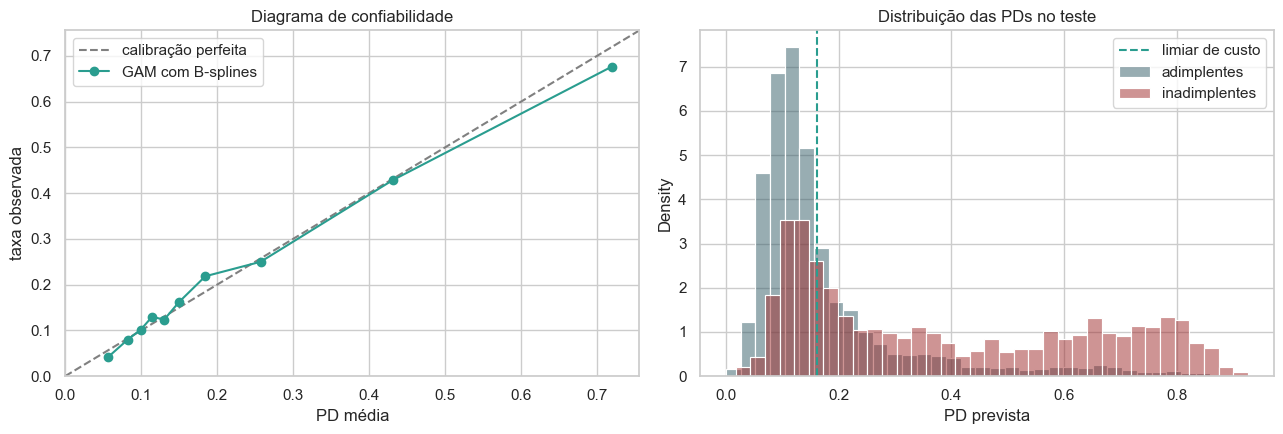

,n,pd_media,taxa_observada
0,600,0.0565,0.0417
1,600,0.0824,0.0800
2,600,0.0996,0.1017
3,600,0.1145,0.1300
4,600,0.1302,0.1233
5,600,0.1497,0.1617
6,600,0.1845,0.2183
7,600,0.2573,0.2500
8,600,0.4310,0.4283
9,600,0.7196,0.6767


In [28]:
def calibration_table(y_true, probability, q=10):
    table = pd.DataFrame({"y": np.asarray(y_true), "p": probability})
    table["bin"] = pd.qcut(table["p"], q=q, duplicates="drop")
    return table.groupby("bin", observed=True).agg(
        n=("y", "size"),
        pd_media=("p", "mean"),
        taxa_observada=("y", "mean"),
    ).reset_index(drop=True)


calibration = calibration_table(y_test, test_probability, q=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot([0, 1], [0, 1], ls="--", color="gray", label="calibração perfeita")
axes[0].plot(calibration["pd_media"], calibration["taxa_observada"], marker="o",
             color=COLORS[selected_kind], label=model_map[selected_kind])
axes[0].set_xlim(0, max(0.65, calibration[["pd_media", "taxa_observada"]].to_numpy().max() * 1.05))
axes[0].set_ylim(0, max(0.65, calibration[["pd_media", "taxa_observada"]].to_numpy().max() * 1.05))
axes[0].set_title("Diagrama de confiabilidade")
axes[0].set_xlabel("PD média")
axes[0].set_ylabel("taxa observada")
axes[0].legend()

sns.histplot(test_probability[y_test.to_numpy() == 0], bins=35, stat="density",
             alpha=0.5, label="adimplentes", ax=axes[1], color="#335C67")
sns.histplot(test_probability[y_test.to_numpy() == 1], bins=35, stat="density",
             alpha=0.5, label="inadimplentes", ax=axes[1], color="#9E2A2B")
axes[1].axvline(best_threshold, color="#2A9D8F", ls="--", label="limiar de custo")
axes[1].set_title("Distribuição das PDs no teste")
axes[1].set_xlabel("PD prevista")
axes[1].legend()

plt.tight_layout()
plt.show()
calibration

### Decisão sobre recalibração

O diagrama do teste é diagnóstico final, não conjunto para reajustar o modelo. Se a calibração ficar inadequada, a próxima versão deve reservar validação temporal ou usar calibração cruzada no treino, com métodos como Platt ou isotônico. Ajustar um calibrador neste teste e publicar a métrica no mesmo conjunto contaminaria a avaliação.

## 14. Política de decisão no teste

<!-- DIDATICA-END-TO-END:politica-decisao -->

### Como ler a matriz de decisão

Com limiar de aproximadamente 0,162, a política sinaliza cerca de 40,3% do teste e captura 71,4% dos inadimplentes. O volume elevado decorre da penalização maior atribuída ao falso negativo.

**Precision.** Entre as contas sinalizadas, aproximadamente 39,2% são inadimplentes. O restante representa falsos positivos sob essa definição de alvo e precisa ser considerado no custo de contato ou restrição.

**Recall.** Cerca de 28,6% dos inadimplentes permanecem sem sinalização. Reduzir esse número exige baixar o limiar e aceitar maior volume.

**Interpretação comercial.** A matriz deve ser traduzida em valores: exposição média dos falsos negativos, margem perdida nos falsos positivos, custo de revisão e taxa de recuperação. Contagens isoladas não mostram a rentabilidade da política.

**Análise de capacidade.** O cenário de 20% responde a outra pergunta: qual fração dos inadimplentes pode ser capturada com uma fila operacional fixa? Essa visão costuma ser mais próxima de cobrança e prevenção.

In [30]:
test_decision = (test_probability >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_decision, labels=[0, 1]).ravel()

policy_metrics = pd.Series({
    "limiar": best_threshold,
    "contas sinalizadas": int(test_decision.sum()),
    "taxa sinalizada": test_decision.mean(),
    "precision": precision_score(y_test, test_decision),
    "recall": recall_score(y_test, test_decision),
    "especificidade": tn / (tn + fp),
    "custo por conta": (5 * fn + fp) / len(y_test),
    "falsos positivos": fp,
    "falsos negativos": fn,
})

display(policy_metrics.to_frame("teste"))
display(pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["real 0", "real 1"],
    columns=["previsto 0", "previsto 1"],
))

,teste
limiar,0.1620
contas sinalizadas,"2,417.0000"
taxa sinalizada,0.4028
precision,0.3918
recall,0.7136
especificidade,0.6854
custo por conta,0.5617
falsos positivos,"1,470.0000"
falsos negativos,380.0000


,previsto 0,previsto 1
real 0,3203,1470
real 1,380,947


In [31]:
# Cenário de capacidade: revisar apenas os 20% maiores riscos.
capacity_threshold = float(np.quantile(test_probability, 0.80))
capacity_pred = (test_probability >= capacity_threshold).astype(int)

capacity_summary = pd.Series({
    "capacidade": 0.20,
    "limiar correspondente": capacity_threshold,
    "taxa efetivamente sinalizada": capacity_pred.mean(),
    "recall de inadimplentes": recall_score(y_test, capacity_pred),
    "bad rate entre sinalizados": y_test[capacity_pred == 1].mean(),
    "bad rate da carteira": y_test.mean(),
})
capacity_summary.to_frame("resultado")

,resultado
capacidade,0.2000
limiar correspondente,0.3213
taxa efetivamente sinalizada,0.2000
recall de inadimplentes,0.4996
bad rate entre sinalizados,0.5525
bad rate da carteira,0.2212


### Pergunta didática 6

Por que o limiar de 0,5 raramente é uma escolha natural para risco de crédito?

<details>
<summary>Resposta guiada</summary>

O valor 0,5 supõe implicitamente prevalência, custos e utilidades muito específicos. Em crédito, a ação depende de perda esperada, exposição, LGD, margem, capacidade de revisão e apetite a risco. Uma conta com PD de 0,20 pode exigir ação se a perda potencial for alta.

</details>

## 15. Análise de falhas e auditoria por grupos

O projeto de referência de risco de crédito separa falsos positivos e falsos negativos para descobrir segmentos fracos. Aqui, o diagnóstico usa o teste apenas depois do congelamento da solução.

<!-- DIDATICA-END-TO-END:falhas-fairness -->

### Por que investigar erros por segmento

A métrica global pode esconder uma região com muitos falsos negativos, categorias pouco representadas ou PDs mal calibradas. Perfis de erro ajudam a distinguir falta de informação, regra inadequada e mudança de população.

**Falso negativo.** Representa risco não sinalizado. A análise deve procurar padrões de atraso, limite, canal, safra e exposição. Prioridade depende do prejuízo associado, não apenas da quantidade.

**Falso positivo.** Pode gerar atrito, redução indevida de limite ou custo de revisão. Uma política comercial precisa medir abandono, receita e reclamação nesses casos.

**Auditoria por sexo.** Retirar `SEX` do modelo evita uso direto, mas não remove proxies nem diferenças históricas. TPR, FPR, taxa sinalizada e Brier por grupo são diagnósticos. A conclusão de fairness exige definição normativa, intervalos de incerteza, análise de causalidade, contestabilidade e acompanhamento.

**Governança.** Segmentos fracos podem receber regra de exceção, coleta adicional ou revisão humana. A intervenção deve ser validada para evitar que uma correção local transfira o problema para outro grupo.

In [32]:
test_analysis = X_test.copy()
test_analysis["y"] = y_test
test_analysis["pd"] = test_probability
test_analysis["prediction"] = test_decision
test_analysis["error"] = np.select(
    [
        (test_analysis["y"] == 1) & (test_analysis["prediction"] == 0),
        (test_analysis["y"] == 0) & (test_analysis["prediction"] == 1),
    ],
    ["falso negativo", "falso positivo"],
    default="acerto",
)

error_profile = (
    test_analysis.groupby("error")
    .agg(
        n=("y", "size"),
        pd_media=("pd", "mean"),
        limite_mediano=("LIMIT_BAL", "median"),
        idade_mediana=("AGE", "median"),
        atraso_mais_recente_mediano=("PAY_1", "median"),
    )
    .sort_values("n", ascending=False)
)
error_profile

,n,pd_media,limite_mediano,idade_mediana,atraso_mais_recente_mediano
error,,,,,
acerto,4150,0.1947,"160,000.0000",34.0000,0.0000
falso positivo,1470,0.3289,"80,000.0000",35.0000,0.0000
falso negativo,380,0.1155,"160,000.0000",34.0000,0.0000


In [34]:
def subgroup_metrics(frame, group_col, threshold):
    rows = []
    for group, data in frame.groupby(group_col):
        pred = (data["pd"] >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(data["y"], pred, labels=[0, 1]).ravel()
        rows.append({
            group_col: group,
            "n": len(data),
            "default_rate": data["y"].mean(),
            "mean_pd": data["pd"].mean(),
            "auc": roc_auc_score(data["y"], data["pd"]),
            "brier": brier_score_loss(data["y"], data["pd"]),
            "tpr": tp / (tp + fn) if tp + fn else np.nan,
            "fpr": fp / (fp + tn) if fp + tn else np.nan,
            "flag_rate": pred.mean(),
        })
    return pd.DataFrame(rows)


sex_audit = subgroup_metrics(test_analysis, "SEX", best_threshold)
sex_audit["SEX"] = sex_audit["SEX"].map({1: "código 1", 2: "código 2"})
sex_audit

,SEX,n,default_rate,mean_pd,auc,brier,tpr,fpr,flag_rate
0,código 1,2402,0.2336,0.2299,0.7746,0.1438,0.7415,0.3210,0.4192
1,código 2,3598,0.2129,0.2176,0.7664,0.1330,0.6932,0.3104,0.3919


### Leitura responsável da auditoria

Diferenças de TPR, FPR ou Brier sinalizam investigação. Elas não provam discriminação nem satisfazem, sozinhas, uma definição de fairness. O atributo foi retirado do treinamento, mas o comportamento histórico e outros preditores podem preservar disparidades. Uma implantação exigiria definição jurídica e normativa de grupos, métricas, tolerâncias, análise de proxies, contestabilidade e acompanhamento temporal.

## 16. Importância por permutação no teste congelado

A importância por permutação mede quanto o log loss piora quando uma coluna bruta perde sua associação com o alvo. Ela inclui todo o pipeline, mas não separa bem variáveis correlacionadas. O resultado é diagnóstico preditivo, não causal.

<!-- DIDATICA-END-TO-END:permutacao -->

### O que a importância mede

A permutação quebra a relação de uma coluna com o alvo e observa quanto o log loss piora. O resultado mede dependência preditiva da solução completa naquela amostra.

**Variáveis correlacionadas.** Faturas e pagamentos de meses próximos carregam informação parecida. Permutar uma delas pode causar pouca perda porque as demais continuam disponíveis. A importância pode ser dividida entre fontes redundantes.

**Sem interpretação causal.** Alta importância de `PAY_1` indica que o modelo usa o atraso recente. Ela não estima quanto a inadimplência mudaria se o código fosse alterado por intervenção.

**Leitura comercial.** O ranking ajuda a priorizar testes de qualidade, disponibilidade e latência das fontes. Remover uma variável para economizar custo exige nova validação do pipeline, pois as demais podem reorganizar seus efeitos.

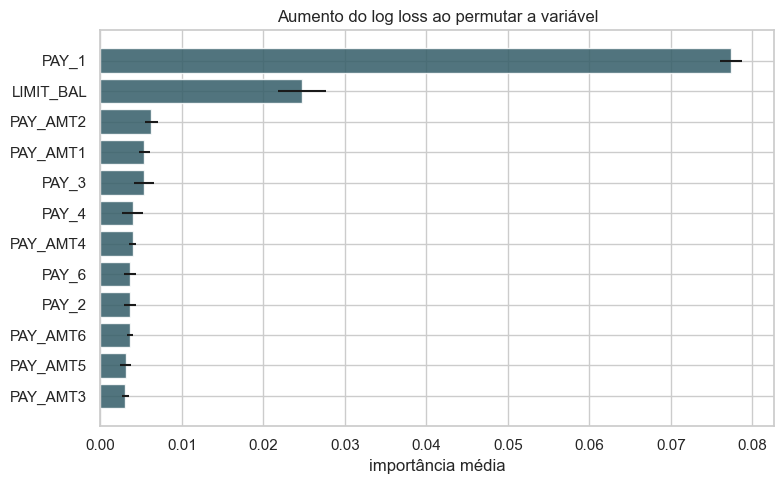

,feature,importance,sd
5,PAY_1,0.0774,0.0014
0,LIMIT_BAL,0.0247,0.0030
18,PAY_AMT2,0.0062,0.0008
17,PAY_AMT1,0.0054,0.0007
7,PAY_3,0.0053,0.0013
8,PAY_4,0.0040,0.0013
20,PAY_AMT4,0.0039,0.0004
10,PAY_6,0.0036,0.0007
6,PAY_2,0.0036,0.0007
22,PAY_AMT6,0.0036,0.0004


In [35]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_log_loss",
    n_repeats=5,
    random_state=SEED,
    n_jobs=1,
)

importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean,
        "sd": perm.importances_std,
    })
    .sort_values("importance", ascending=False)
    .head(12)
)

plt.figure(figsize=(8, 5))
plt.barh(importance["feature"][::-1], importance["importance"][::-1],
         xerr=importance["sd"][::-1], color="#335C67", alpha=0.85)
plt.title("Aumento do log loss ao permutar a variável")
plt.xlabel("importância média")
plt.tight_layout()
plt.show()
importance

## 17. Persistência com pickle

O pickle armazenará:

- o pipeline ajustado, com engenharia, imputação, codificação, bases spline, escalas e coeficientes;
- a ordem e os nomes esperados das colunas brutas;
- o limiar de decisão;
- métricas finais, versão do modelo e versões das bibliotecas;
- um perfil simples de referência para monitoramento.

O pickle não armazena o significado de negócio das colunas, regras jurídicas, consulta SQL, qualidade da origem, política de aprovação nem garantia de compatibilidade entre versões futuras. Como o pipeline contém a classe `CreditFeatureEngineer`, o código dessa classe deve existir no ambiente que carrega o artefato. Em produção, ela ficaria em um pacote versionado e testado.

<!-- DIDATICA-END-TO-END:pickle -->

### O papel do pickle no ciclo operacional

O arquivo serializa o estado ajustado do pipeline: regras da classe, imputadores, escalas, categorias, bases spline e coeficientes. O scoring consegue repetir as mesmas transformações sem executar novo `fit`.

**Ordem e nomes.** A rotina reorganiza colunas pelo contrato salvo, então embaralhar a ordem não altera a PD. Uma coluna ausente interrompe o lote porque o modelo não possui informação para reconstruí-la. Preencher silenciosamente com zero mudaria o significado da observação.

**Dependência de código.** A classe `CreditFeatureEngineer` precisa existir em módulo compatível. Para produção, ela deveria integrar um pacote versionado com testes e dependências fixas.

**Segurança.** Pickle pode executar código durante a carga. Nunca carregue artefatos de origem não confiável. Integridade, assinatura, controle de acesso e trilha de publicação fazem parte do processo.

**Leitura comercial.** O artefato deve estar ligado a versão, data de aprovação, população, limiar, responsável, métricas e plano de rollback. Salvar apenas `modelo.pkl` não fornece governança suficiente.

In [36]:
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
artifact_path = artifact_dir / "modelo_pd_gam.pkl"

training_profile = {
    "LIMIT_BAL_quantiles": X_train["LIMIT_BAL"].quantile([0.01, 0.50, 0.99]).to_dict(),
    "AGE_quantiles": X_train["AGE"].quantile([0.01, 0.50, 0.99]).to_dict(),
    "target_rate": float(y_train.mean()),
    "oof_pd_quantiles": pd.Series(oof_probability).quantile([0.01, 0.50, 0.99]).to_dict(),
}

artifact = {
    "model_version": "1.0.0",
    "model_family": model_map[selected_kind],
    "model": final_model,
    "raw_feature_names": X_train.columns.tolist(),
    "audit_only_columns": AUDIT_COLUMNS,
    "decision_threshold": best_threshold,
    "cost_assumption": {"false_negative": 5.0, "false_positive": 1.0},
    "test_metrics": test_metrics,
    "training_profile": training_profile,
    "library_versions": versions.to_dict(),
    "random_seed": SEED,
}

with artifact_path.open("wb") as file:
    pickle.dump(artifact, file, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Artefato salvo em: {artifact_path.resolve()}")
print(f"Tamanho: {artifact_path.stat().st_size / 1024:.1f} KiB")

Artefato salvo em: C:\Users\daler\OneDrive\Documentos\python-scripts\ISLP\artifacts\modelo_pd_gam.pkl
Tamanho: 9.0 KiB


In [46]:
loaded_artifact["model"]
loaded_artifact["audit_only_columns"]
loaded_artifact["raw_feature_names"]

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

### 17.1 Carga, contrato e scoring de lote

O código abaixo simula uma rotina diária. A ordem recebida pode mudar porque a função reorganiza as colunas pelos nomes. Uma coluna obrigatória ausente interrompe o scoring. Preencher silenciosamente uma variável ausente com zero criaria uma população diferente daquela usada no treinamento.

In [37]:
with artifact_path.open("rb") as file:
    loaded_artifact = pickle.load(file)


def score_batch(artifact, batch):
    expected = artifact["raw_feature_names"]
    missing = sorted(set(expected) - set(batch.columns))
    extra = sorted(set(batch.columns) - set(expected))
    if missing:
        raise ValueError(f"Scoring cancelado. Colunas ausentes: {missing}")
    if extra:
        warnings.warn(f"Colunas extras serão ignoradas: {extra}")

    ordered = batch.loc[:, expected]
    probability = artifact["model"].predict_proba(ordered)[:, 1]
    decision = (probability >= artifact["decision_threshold"]).astype(int)
    return pd.DataFrame({"pd": probability, "sinalizar": decision}, index=batch.index)


sample_batch = X_test.sample(8, random_state=SEED)
shuffled_batch = sample_batch.sample(frac=1, axis=1, random_state=SEED)

score_original = score_batch(loaded_artifact, sample_batch)
score_shuffled = score_batch(loaded_artifact, shuffled_batch)

assert np.allclose(score_original["pd"], score_shuffled["pd"])
print("Maior diferença após embaralhar colunas:",
      np.max(np.abs(score_original["pd"] - score_shuffled["pd"])))
score_original

Maior diferença após embaralhar colunas: 0.0


,pd,sinalizar
20639,0.3136,1
7660,0.7134,1
13980,0.0885,0
7162,0.6105,1
24017,0.1152,0
499,0.3818,1
10858,0.1235,0
6463,0.0801,0


In [38]:
try:
    broken_batch = sample_batch.drop(columns="BILL_AMT3")
    score_batch(loaded_artifact, broken_batch)
except ValueError as error:
    print(type(error).__name__ + ":", error)

ValueError: Scoring cancelado. Colunas ausentes: ['BILL_AMT3']


### Pergunta didática 7

Se o modelo foi salvo, por que ele não consegue prever quando falta uma das 23 colunas?

<details>
<summary>Resposta guiada</summary>

O objeto salvo contém uma função já ajustada que espera a mesma estrutura usada no fit. Coeficientes e transformadores correspondem a entradas específicas. O pickle conserva o estado do objeto; ele não inventa o valor desconhecido nem redefine o modelo quando uma variável some. A ordem pode ser resolvida pelos nomes. Ausência e mudança semântica exigem tratamento explícito.

</details>

## 18. Monitoramento com PSI

O Population Stability Index compara a proporção de observações em faixas de referência. Ele detecta mudança de distribuição, não queda de performance. Uma carteira pode manter PSI baixo e sofrer mudança na relação entre $X$ e $Y$.

Faixas usuais de 0,10 e 0,25 são apenas alertas operacionais. Elas não são leis estatísticas universais.

<!-- DIDATICA-END-TO-END:monitoramento -->

### O que monitorar depois da implantação

PSI compara a distribuição atual com a referência. Ele detecta mudança de população, como alteração de limites ou composição da carteira. O cenário com limite 30% menor mostra como uma mudança operacional pode elevar o indicador.

**Limitação.** PSI baixo não garante que a relação entre preditores e inadimplência permaneceu estável. Pode ocorrer concept drift com distribuição de entrada semelhante. Quando o alvo chega, AUC, Gini, log loss, Brier, calibração e custo precisam ser recalculados.

**Monitoramento em camadas.** Antes do alvo, acompanhe esquema, nulos, categorias novas, faixas, PSI e distribuição das PDs. Depois do alvo, acompanhe desempenho por safra, segmento e decisão. Junto deles, registre volume, aprovação, perda, receita e reclamação.

**Gatilhos comerciais.** Alertas devem levar a ações definidas: investigar fonte, suspender scoring, retornar ao champion anterior, recalibrar ou desenvolver nova versão. Um painel sem responsável e resposta acordada não controla risco.

In [39]:
def population_stability_index(reference, current, bins=10):
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    ref_counts = np.histogram(reference, bins=edges)[0] / len(reference)
    cur_counts = np.histogram(current, bins=edges)[0] / len(current)
    ref_counts = np.clip(ref_counts, 1e-6, None)
    cur_counts = np.clip(cur_counts, 1e-6, None)
    return float(np.sum((cur_counts - ref_counts) * np.log(cur_counts / ref_counts)))


shifted_limits = X_test["LIMIT_BAL"] * 0.70
psi_table = pd.DataFrame({
    "comparação": ["treino x teste aleatório", "treino x cenário com limite 30% menor"],
    "PSI_LIMIT_BAL": [
        population_stability_index(X_train["LIMIT_BAL"], X_test["LIMIT_BAL"]),
        population_stability_index(X_train["LIMIT_BAL"], shifted_limits),
    ],
})
psi_table

,comparação,PSI_LIMIT_BAL
0,treino x teste aleatório,0.0016
1,treino x cenário com limite 30% menor,0.5212


## 19. Testes mínimos antes da entrega

<!-- DIDATICA-END-TO-END:testes -->

### Como ampliar os testes para produção

Os asserts confirmam isolamento do teste, ausência de alvo e ID, domínio das probabilidades, reprodução após pickle e invariância à ordem das colunas.

Uma implantação acrescentaria:

- tipos, unidades e faixas por coluna;
- categorias desconhecidas e valores extremos;
- lote vazio, duplicado ou parcialmente ausente;
- igualdade entre scoring online e batch;
- latência, memória e volume máximo;
- comparação golden set entre versões;
- falha segura quando a origem quebra o contrato;
- teste de rollback e recuperação do artefato anterior.

**Leitura comercial.** Teste técnico evita decisões silenciosamente erradas. O custo de bloquear um lote é visível; o custo de produzir milhares de PDs incorretas costuma aparecer depois, em perdas e reclamações.

In [29]:
roundtrip_probability = loaded_artifact["model"].predict_proba(X_test.iloc[:50])[:, 1]
original_probability = final_model.predict_proba(X_test.iloc[:50])[:, 1]

checks = {
    "teste isolado do treino": set(X_train.index).isdisjoint(X_test.index),
    "alvo fora dos preditores": TARGET not in X_train.columns,
    "ID fora dos preditores": "ID" not in X_train.columns,
    "probabilidades finitas": bool(np.isfinite(test_probability).all()),
    "probabilidades em [0, 1]": bool(((test_probability >= 0) & (test_probability <= 1)).all()),
    "pickle reproduz previsões": bool(np.allclose(roundtrip_probability, original_probability)),
    "ordem de colunas não altera PD": bool(np.allclose(score_original["pd"], score_shuffled["pd"])),
}

assert all(checks.values())
pd.Series(checks, name="passou").to_frame()

Out[0]: 
                                passou
teste isolado do treino           True
alvo fora dos preditores          True
ID fora dos preditores            True
probabilidades finitas            True
probabilidades em [0, 1]          True
pickle reproduz previsões         True
ordem de colunas não altera PD    True


## 20. Conclusão executiva gerada pelos resultados

<!-- DIDATICA-END-TO-END:conclusao-governanca -->

### Julgamento final do projeto

O notebook demonstra que formas flexíveis capturam estrutura além do termo linear e que o GAM oferece bom compromisso entre ranking, log loss e continuidade. A escolha foi feita por validação, com teste aberto somente depois do congelamento.

**Uso permitido desta versão.** Estudo metodológico, comparação de técnicas e simulação de um fluxo de risco de crédito.

**Pendências para implantação.** Dados atuais da carteira-alvo, definição institucional de default, validação temporal, EAD e LGD, calibração por safra, análise de aprovação histórica, fairness, explicações de decisão, monitoramento, segurança e aprovação de modelo.

**Decisão comercial.** AUC e Gini mostram capacidade de ordenação; o limiar de 0,162 mostra uma política construída sob custo hipotético. O business case deve substituir essa hipótese por perdas, receita, capacidade e experiência do cliente antes de qualquer uso operacional.

In [30]:
display(Markdown(f"""
O modelo selecionado foi **{model_map[selected_kind]}**, com `{final_search.best_params_}`. No teste fechado, obteve **AUC de {test_metrics['roc_auc']:.3f}**, **Gini de {test_metrics['gini']:.3f}**, **log loss de {test_metrics['log_loss']:.3f}** e **Brier de {test_metrics['brier']:.3f}**.

Com custo de falso negativo cinco vezes maior que o de falso positivo, o limiar escolhido apenas com previsões fora da amostra do treino foi **{best_threshold:.3f}**. No teste, essa política sinalizou **{test_decision.mean():.1%}** das contas e capturou **{recall_score(y_test, test_decision):.1%}** dos inadimplentes.

A melhoria de formas flexíveis sobre o termo linear mostra que a não linearidade tem utilidade preditiva neste problema. A escolha do GAM considera a incerteza entre dobras e evita os saltos da função degrau. O resultado continua limitado pelo recorte histórico, pela ausência de validação temporal e pela falta de variáveis como exposição, LGD e retorno.
"""))


O modelo selecionado foi **GAM com B-splines**, com `{'model__C': 0.1, 'preprocess__focus__spline__n_knots': 7}`. No teste fechado, obteve **AUC de 0.770**, **Gini de 0.540**, **log loss de 0.437** e **Brier de 0.137**.

Com custo de falso negativo cinco vezes maior que o de falso positivo, o limiar escolhido apenas com previsões fora da amostra do treino foi **0.162**. No teste, essa política sinalizou **40.3%** das contas e capturou **71.4%** dos inadimplentes.

A melhoria de formas flexíveis sobre o termo linear mostra que a não linearidade tem utilidade preditiva neste problema. A escolha do GAM considera a incerteza entre dobras e evita os saltos da função degrau. O resultado continua limitado pelo recorte histórico, pela ausência de validação temporal e pela falta de variáveis como exposição, LGD e retorno.


## 21. Perguntas para aprofundar

1. Como você adaptaria o split se houvesse uma data de referência mensal?
2. O que mudaria na validação se várias linhas pertencessem ao mesmo cliente?
3. Em qual situação `class_weight="balanced"` melhora recall e piora a PD?
4. Como corrigir a calibração após oversampling?
5. Por que selecionar grau polinomial com desempenho no treino viola o raciocínio do Capítulo 7?
6. Quais sinais no gráfico indicariam comportamento instável na borda?
7. Como comparar um GAM aditivo com um modelo que permita interação entre limite e atraso?
8. Por que importância por permutação pode dividir ou esconder importância entre faturas correlacionadas?
9. Como converter o custo fixo de falso negativo em perda esperada com `PD × EAD × LGD`?
10. Que dados e controles seriam necessários para usar a saída em uma política de crédito real?
11. Que testes deveriam bloquear o deploy quando a fonte altera tipos, códigos ou unidade monetária?
12. Como monitorar discriminação e calibração quando o alvo chega com atraso?

## 22. Extensões recomendadas

- validação out-of-time com janelas móveis;
- comparação com boosting mantendo o GAM como benchmark interpretável;
- calibração cruzada escolhida somente no treino;
- intervalos de confiança para curvas parciais via bootstrap;
- monotonicidade para variáveis com restrição de negócio defensável;
- estabilidade de coeficientes, nós e métricas por safra;
- análise de fairness com definição de grupos e critérios acordados;
- pacote Python com `CreditFeatureEngineer`, testes unitários e versionamento de esquema;
- registro de modelo, aprovação, champion/challenger e rollback.

## 23. Referências

### Materiais centrais

- James, Witten, Hastie, Tibshirani e Taylor. *An Introduction to Statistical Learning with Applications in Python*, Capítulo 7, Moving Beyond Linearity. PDF fornecido e [laboratório oficial](https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch07-nonlin-lab.ipynb).
- [Soluções aplicadas do Capítulo 7](https://github.com/KarimABOUSSELHAM/ISLP-applied-solutions/blob/main/Chapter%207.ipynb).
- Géron. [End-to-End Machine Learning Project](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb).
- Inria. [Scikit-learn MOOC](https://inria.github.io/scikit-learn-mooc/toc.html), [validação cruzada](https://inria.github.io/scikit-learn-mooc/python_scripts/02_numerical_pipeline_cross_validation.html) e [validação aninhada](https://inria.github.io/scikit-learn-mooc/python_scripts/cross_validation_nested.html).
- Faustino. [CreditRiskProject](https://github.com/IohanFaustino/CreditRiskProject) e [notebooks em português](https://github.com/IohanFaustino/CreditRiskProject/tree/main/notebooks/version/pt).

### Dados e documentação técnica

- Yeh e Lien. [Default of Credit Card Clients](https://archive.ics.uci.edu/ml/datasets/default%2Bof%2Bcredit%2Bcard%2Bclients), UCI Machine Learning Repository.
- Scikit-learn. [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), [`SplineTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html), [calibração](https://scikit-learn.org/stable/modules/calibration.html) e [`brier_score_loss`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html).

### Referências em português

- Banco Central do Brasil. [Aferindo o poder discriminatório dos modelos de classificação de risco de crédito](https://www4.bcb.gov.br/pre/inscricaoContaB/trabalhos/Aferindo%20o%20Poder%20Discriminat%C3%B3rio%20dos%20Modelos%20de%20Classifica%C3%A7%C3%A3o%20de%20Risco%20de%20Cr%C3%A9dito.pdf).
- Vieira. [Risco de crédito e a aplicação da modelagem por regressão logística](https://repositorio.unesp.br/bitstreams/92638ccd-bd0d-427a-a651-abfc73b134f3/download), UNESP.